# Connect data

In [4]:
import json
import random
import sys
import tarfile
import time
from pathlib import Path

import numpy as np
import pandas as pd
import torch

from google.colab import drive
from torch.utils.data import DataLoader


assert torch.cuda.is_available(), "Connect the A100 GPU first"
assert "A100" in torch.cuda.get_device_name(0)

PROJECT_ROOT = Path("/content/drive/MyDrive/MADSeg")
LOCAL_ROOT = Path("/content/MADSeg_data")

CACHE_TAR = (
    PROJECT_ROOT
    / "cache"
    / "multiannotator_local_v1.tar"
)

INDEX_CSV = (
    PROJECT_ROOT
    / "audit_results"
    / "multiannotator_index.csv"
)

assert CACHE_TAR.exists(), CACHE_TAR
assert INDEX_CSV.exists(), INDEX_CSV

multi_index = pd.read_csv(INDEX_CSV)

assert len(multi_index) == 2394
assert multi_index["isic_id"].is_unique

def local_data_complete():
    image_directory = LOCAL_ROOT / "images"
    mask_directory = LOCAL_ROOT / "segs"

    if not image_directory.exists() or not mask_directory.exists():
        return False

    image_count = sum(
        path.is_file()
        for path in image_directory.iterdir()
    )

    mask_count = sum(
        path.is_file()
        for path in mask_directory.iterdir()
    )

    return image_count >= 2394 and mask_count >= 9899

if local_data_complete():
    print("Runtime-local multi-annotator data already exists.")

else:
    LOCAL_ROOT.mkdir(parents=True, exist_ok=True)

    print("Restoring persistent TAR cache...")
    print(
        "Archive size:",
        f"{CACHE_TAR.stat().st_size / 1024**3:.2f} GB",
    )

    extraction_start = time.perf_counter()

    with tarfile.open(CACHE_TAR, mode="r") as archive:
        member_names = [
            member.name
            for member in archive.getmembers()[:10]
        ]

        normalized_names = [
            name.lstrip("./")
            for name in member_names
        ]

        if any(
            name.startswith("MADSeg_data/")
            for name in normalized_names
        ):
            extraction_root = Path("/content")
        else:
            extraction_root = LOCAL_ROOT

        try:
            archive.extractall(
                extraction_root,
                filter="data",
            )
        except TypeError:
            archive.extractall(extraction_root)

    print(
        "Extraction time:",
        f"{time.perf_counter() - extraction_start:.1f}s",
    )

assert local_data_complete(), (
    "TAR extraction did not produce the expected "
    "images and masks."
)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import importlib
import multiannotator_data

importlib.reload(multiannotator_data)

from multiannotator_data import MultiAnnotatorDataset

MULTI_ANNOTATORS = [
    "A00", "A01", "A02", "A03",
    "A04", "A05", "A06", "A07",
    "A08", "A09", "A10", "A11",
    "A12", "A14", "A15",
]

ANNOTATOR_TO_ID = {
    value: index
    for index, value in enumerate(MULTI_ANNOTATORS)
}

TOOL_TO_ID = {
    value: index
    for index, value in enumerate(["T1", "T2", "T3"])
}

SKILL_TO_ID = {
    value: index
    for index, value in enumerate(["S1", "S2"])
}

train_frame = multi_index[
    multi_index["split"] == "train"
].reset_index(drop=True)

validation_frame = multi_index[
    multi_index["split"] == "validation"
].reset_index(drop=True)

test_frame = multi_index[
    multi_index["split"] == "test"
].reset_index(drop=True)

train_dataset = MultiAnnotatorDataset(
    frame=train_frame,
    local_root=LOCAL_ROOT,
    annotator_to_id=ANNOTATOR_TO_ID,
    tool_to_id=TOOL_TO_ID,
    skill_to_id=SKILL_TO_ID,
    image_size=352,
    augment=True,
)

validation_dataset = MultiAnnotatorDataset(
    frame=validation_frame,
    local_root=LOCAL_ROOT,
    annotator_to_id=ANNOTATOR_TO_ID,
    tool_to_id=TOOL_TO_ID,
    skill_to_id=SKILL_TO_ID,
    image_size=352,
    augment=False,
)

test_dataset = MultiAnnotatorDataset(
    frame=test_frame,
    local_root=LOCAL_ROOT,
    annotator_to_id=ANNOTATOR_TO_ID,
    tool_to_id=TOOL_TO_ID,
    skill_to_id=SKILL_TO_ID,
    image_size=352,
    augment=False,
)

SEED = 442
BATCH_SIZE = 16
NUM_WORKERS = 8

v2_loader_generator = torch.Generator()
v2_loader_generator.manual_seed(SEED)

def v2_seed_worker(worker_id):
    worker_seed = torch.initial_seed() % (2**32)
    np.random.seed(worker_seed)
    random.seed(worker_seed)

loader_options = {
    "batch_size": BATCH_SIZE,
    "num_workers": NUM_WORKERS,
    "pin_memory": True,
    "persistent_workers": True,
    "prefetch_factor": 2,
    "worker_init_fn": v2_seed_worker,
}

v2_train_loader = DataLoader(
    train_dataset,
    shuffle=True,
    drop_last=True,
    generator=v2_loader_generator,
    **loader_options,
)

v2_validation_loader = DataLoader(
    validation_dataset,
    shuffle=False,
    drop_last=False,
    **loader_options,
)

assert len(v2_train_loader) == 104
assert len(v2_validation_loader) == 15

print("\nDATA PIPELINE RESTORED")
print("GPU:", torch.cuda.get_device_name(0))
print("Training:", len(train_dataset), len(v2_train_loader))
print(
    "Validation:",
    len(validation_dataset),
    len(v2_validation_loader),
)
print("Test:", len(test_dataset))
print("Test loader has not been iterated.")

Restoring persistent TAR cache...
Archive size: 1.81 GB
Extraction time: 35.8s

DATA PIPELINE RESTORED
GPU: NVIDIA A100-SXM4-40GB
Training: 1675 104
Validation: 240 15
Test: 479
Test loader has not been iterated.


In [5]:
import os
import json
import time
import random
import importlib
from pathlib import Path

import numpy as np
import pandas as pd
import torch

from tqdm.auto import tqdm

import madseg_model
import madseg_v2_losses
import madseg_v2_objective

importlib.reload(madseg_model)
importlib.reload(madseg_v2_losses)
importlib.reload(madseg_v2_objective)

from madseg_model import MADSeg
from madseg_v2_objective import MADSegV2Loss

device = torch.device("cuda")

RUN_ROOT = (
    PROJECT_ROOT
    / "outputs"
    / "madseg_stage2_v2_roi_balanced_v1"
)

INITIALIZATION_CHECKPOINT = (
    PROJECT_ROOT
    / "outputs"
    / "madseg_stage2_initialization"
    / "madseg_stage2_initialization.pt"
)

BEST_CHECKPOINT = RUN_ROOT / "best_checkpoint.pt"
LAST_CHECKPOINT = RUN_ROOT / "last_checkpoint.pt"
HISTORY_CSV = RUN_ROOT / "history.csv"
CURVE_PATH = RUN_ROOT / "training_curves.png"

MAXIMUM_EPOCHS = 30
EARLY_STOPPING_PATIENCE = 5
GRADIENT_CLIP_NORM = 1.0

assert LAST_CHECKPOINT.exists(), (
    f"No resumable checkpoint found: {LAST_CHECKPOINT}"
)

initialization = torch.load(
    INITIALIZATION_CHECKPOINT,
    map_location="cpu",
    weights_only=False,
)

resume_checkpoint = torch.load(
    LAST_CHECKPOINT,
    map_location="cpu",
    weights_only=False,
)

assert (
    resume_checkpoint.get("version")
    == "v2_roi_balanced_disagreement"
)

model = MADSeg(
    in_channels=3,
    base_channels=16,
    number_of_annotators=15,
    number_of_tools=3,
    number_of_skills=2,
    embedding_dimension=8,
).to(device)

pretrained_prefixes = (
    "encoder.",
    "shared_encoder.",
    "consensus_decoder.",
    "consensus_head.",
    "raw_consensus_head.",
)

pretrained_parameters = []
new_branch_parameters = []

for name, parameter in model.named_parameters():
    if name.startswith(pretrained_prefixes):
        pretrained_parameters.append(parameter)
    else:
        new_branch_parameters.append(parameter)

assert pretrained_parameters
assert new_branch_parameters

criterion = MADSegV2Loss(
    lambda_segmentation=1.0,
    lambda_soft_consensus=0.5,
    lambda_boundary=0.3,
    lambda_disagreement=0.3,
    lambda_annotator=0.5,
    lambda_consistency=0.1,
    roi_dilation_radius=8,
    active_threshold=0.05,
    correlation_weight=0.25,
    disagreement_global_weight=0.05,
).to(device)

optimizer = torch.optim.AdamW(
    [
        {
            "params": pretrained_parameters,
            "lr": 2e-4,
            "name": "pretrained",
        },
        {
            "params": new_branch_parameters,
            "lr": 1e-3,
            "name": "new_branches",
        },
    ],
    weight_decay=1e-4,
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2,
    threshold=1e-4,
    threshold_mode="rel",
    min_lr=1e-6,
)

model.load_state_dict(
    resume_checkpoint["model_state"],
    strict=True,
)

optimizer.load_state_dict(
    resume_checkpoint["optimizer_state"]
)

scheduler.load_state_dict(
    resume_checkpoint["scheduler_state"]
)

history = resume_checkpoint["history"]

best_validation_score = float(
    resume_checkpoint["best_validation_score"]
)

epochs_without_improvement = int(
    resume_checkpoint["epochs_without_improvement"]
)

completed_epoch = int(resume_checkpoint["epoch"])
start_epoch = completed_epoch + 1

configuration = resume_checkpoint["config"]

# Restore random states after constructing all objects.
if "python_rng_state" in resume_checkpoint:
    random.setstate(
        resume_checkpoint["python_rng_state"]
    )

if "numpy_rng_state" in resume_checkpoint:
    np.random.set_state(
        resume_checkpoint["numpy_rng_state"]
    )

if "torch_rng_state" in resume_checkpoint:
    torch.set_rng_state(
        resume_checkpoint["torch_rng_state"]
    )

if "cuda_rng_state" in resume_checkpoint:
    torch.cuda.set_rng_state_all(
        resume_checkpoint["cuda_rng_state"]
    )

if "loader_generator_state" in resume_checkpoint:
    v2_loader_generator.set_state(
        resume_checkpoint["loader_generator_state"]
    )

LOSS_NAMES = [
    "total",
    "segmentation",
    "soft_consensus",
    "boundary",
    "disagreement",
    "disagreement_balanced_regression",
    "disagreement_correlation",
    "disagreement_global",
    "annotator",
    "consistency",
]

def move_to_device(batch):
    return {
        key: (
            value.to(device, non_blocking=True)
            if torch.is_tensor(value)
            else value
        )
        for key, value in batch.items()
    }

def forward_model(batch):
    return model(
        image=batch["image"],
        annotator_ids=batch["annotator_ids"],
        tool_ids=batch["tool_ids"],
        skill_ids=batch["skill_ids"],
        return_annotator_logits=True,
    )

def dice_per_map(prediction, target, epsilon=1e-6):
    prediction = prediction.float()
    target = target.float()

    intersection = (
        prediction * target
    ).sum(dim=(-2, -1))

    denominator = (
        prediction.sum(dim=(-2, -1))
        + target.sum(dim=(-2, -1))
    )

    return (
        2.0 * intersection + epsilon
    ) / (
        denominator + epsilon
    )

def atomic_torch_save(payload, destination):
    temporary = destination.with_suffix(
        destination.suffix + ".temporary"
    )

    torch.save(payload, temporary)
    os.replace(temporary, destination)

def checkpoint_payload(
    epoch,
    history,
    best_score,
    epochs_without_improvement,
):
    return {
        "stage": 2,
        "version": "v2_roi_balanced_disagreement",
        "epoch": epoch,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "scheduler_state": scheduler.state_dict(),
        "scaler_state": None,
        "best_validation_score": best_score,
        "epochs_without_improvement": (
            epochs_without_improvement
        ),
        "history": history,
        "config": configuration,
        "source_initialization": str(
            INITIALIZATION_CHECKPOINT
        ),
        "python_rng_state": random.getstate(),
        "numpy_rng_state": np.random.get_state(),
        "torch_rng_state": torch.get_rng_state(),
        "cuda_rng_state": torch.cuda.get_rng_state_all(),
        "loader_generator_state": (
            v2_loader_generator.get_state()
        ),
        "test_set_evaluated": False,
    }

def train_one_epoch():
    model.train()

    accumulated = {
        name: 0.0 for name in LOSS_NAMES
    }
    images_processed = 0

    for batch in tqdm(
        v2_train_loader,
        desc="Training",
        leave=False,
    ):
        batch = move_to_device(batch)
        batch_size = batch["image"].shape[0]

        optimizer.zero_grad(set_to_none=True)

        with torch.autocast(
            device_type="cuda",
            dtype=torch.bfloat16,
        ):
            outputs = forward_model(batch)
            losses = criterion(outputs, batch)

        assert torch.isfinite(losses["total"])

        losses["total"].backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            GRADIENT_CLIP_NORM,
        )

        optimizer.step()

        for name in LOSS_NAMES:
            accumulated[name] += (
                float(losses[name].detach())
                * batch_size
            )

        images_processed += batch_size

    return {
        name: value / images_processed
        for name, value in accumulated.items()
    }

@torch.inference_mode()
def validate():
    model.eval()

    accumulated = {
        name: 0.0 for name in LOSS_NAMES
    }

    metric_sums = {
        "expected_human_dice": 0.0,
        "consensus_dice": 0.0,
        "staple_dice": 0.0,
        "majority_dice": 0.0,
        "boundary_head_dice": 0.0,
        "disagreement_head_mae": 0.0,
        "annotator_branch_dice": 0.0,
    }

    images_processed = 0

    for batch in tqdm(
        v2_validation_loader,
        desc="Validation",
        leave=False,
    ):
        batch = move_to_device(batch)
        batch_size = batch["image"].shape[0]

        with torch.autocast(
            device_type="cuda",
            dtype=torch.bfloat16,
        ):
            outputs = forward_model(batch)
            losses = criterion(outputs, batch)

        for name in LOSS_NAMES:
            accumulated[name] += (
                float(losses[name]) * batch_size
            )

        final_prediction = (
            torch.sigmoid(
                outputs["final_mask_logits"].float()
            ) >= 0.5
        ).float()

        repeated_prediction = final_prediction.expand(
            -1,
            batch["human_masks"].shape[1],
            -1,
            -1,
        )

        human_dice = dice_per_map(
            repeated_prediction,
            batch["human_masks"],
        )

        valid_masks = batch["mask_valid"].float()

        expected_human = (
            (human_dice * valid_masks).sum(dim=1)
            / valid_masks.sum(dim=1).clamp_min(1.0)
        )

        consensus = dice_per_map(
            final_prediction,
            batch["hard_consensus"],
        ).squeeze(1)

        staple = dice_per_map(
            final_prediction,
            batch["staple_mask"],
        ).squeeze(1)

        majority = dice_per_map(
            final_prediction,
            batch["majority_mask"],
        ).squeeze(1)

        boundary_prediction = (
            torch.sigmoid(
                outputs["boundary_logits"].float()
            ) >= 0.5
        ).float()

        boundary_target = (
            batch["boundary_probability"] >= 0.5
        ).float()

        boundary_dice = dice_per_map(
            boundary_prediction,
            boundary_target,
        ).squeeze(1)

        disagreement_mae = (
            torch.sigmoid(
                outputs["disagreement_logits"].float()
            )
            - batch["human_disagreement"]
        ).abs().flatten(1).mean(dim=1)

        annotator_prediction = (
            torch.sigmoid(
                outputs["annotator_logits"].float()
            ) >= 0.5
        ).float()

        annotator_dice = dice_per_map(
            annotator_prediction,
            batch["human_masks"],
        )

        expected_annotator = (
            (annotator_dice * valid_masks).sum(dim=1)
            / valid_masks.sum(dim=1).clamp_min(1.0)
        )

        metric_sums["expected_human_dice"] += float(
            expected_human.sum()
        )
        metric_sums["consensus_dice"] += float(
            consensus.sum()
        )
        metric_sums["staple_dice"] += float(
            staple.sum()
        )
        metric_sums["majority_dice"] += float(
            majority.sum()
        )
        metric_sums["boundary_head_dice"] += float(
            boundary_dice.sum()
        )
        metric_sums["disagreement_head_mae"] += float(
            disagreement_mae.sum()
        )
        metric_sums["annotator_branch_dice"] += float(
            expected_annotator.sum()
        )

        images_processed += batch_size

    result = {
        f"validation_{name}_loss": (
            value / images_processed
        )
        for name, value in accumulated.items()
    }

    result.update({
        name: value / images_processed
        for name, value in metric_sums.items()
    })

    return result

print("\nMAD-SEG V2 CHECKPOINT RESTORED")
print("GPU:", torch.cuda.get_device_name(0))
print("Completed epoch:", completed_epoch)
print("Resume from epoch:", start_epoch)
print(
    "Best validation expected-human Dice:",
    f"{best_validation_score:.6f}",
)
print(
    "Patience state:",
    f"{epochs_without_improvement}/"
    f"{EARLY_STOPPING_PATIENCE}",
)
print(
    "Current learning rates:",
    [group["lr"] for group in optimizer.param_groups],
)
print("History rows:", len(history))
print("Checkpoint:", LAST_CHECKPOINT)
print("Test images accessed: 0")
print("Ready to continue training.")


MAD-SEG V2 CHECKPOINT RESTORED
GPU: NVIDIA A100-SXM4-40GB
Completed epoch: 19
Resume from epoch: 20
Best validation expected-human Dice: 0.851581
Patience state: 5/5
Current learning rates: [5e-05, 0.00025]
History rows: 20
Checkpoint: /content/drive/MyDrive/MADSeg/outputs/madseg_stage2_v2_roi_balanced_v1/last_checkpoint.pt
Test images accessed: 0
Ready to continue training.


In [6]:
import json
from pathlib import Path

import pandas as pd
import torch

history_frame = pd.DataFrame(history)

trained_history = history_frame[
    history_frame["epoch"] > 0
].copy()

best_row = history_frame.loc[
    history_frame[
        "expected_human_dice"
    ].idxmax()
]

best_epoch = int(best_row["epoch"])
best_score = float(
    best_row["expected_human_dice"]
)

best_checkpoint = torch.load(
    BEST_CHECKPOINT,
    map_location="cpu",
    weights_only=False,
)

assert int(best_checkpoint["epoch"]) == best_epoch
assert (
    abs(
        float(best_checkpoint["best_validation_score"])
        - best_score
    )
    < 5e-5
)

model.load_state_dict(
    best_checkpoint["model_state"],
    strict=True,
)

# Re-evaluate only validation to verify the selected checkpoint.
locked_validation = validate()

restoration_difference = abs(
    float(
        locked_validation["expected_human_dice"]
    )
    - best_score
)

assert restoration_difference < 5e-5

locked_summary = {
    "run_name": RUN_ROOT.name,
    "training_status": "early_stopped",
    "epochs_completed": int(
        history_frame["epoch"].max()
    ),
    "best_epoch": best_epoch,
    "early_stopping_patience": 5,
    "final_patience_state": (
        epochs_without_improvement
    ),
    "best_validation_expected_human_dice": (
        best_score
    ),
    "restored_validation_metrics": {
        key: float(value)
        for key, value in locked_validation.items()
    },
    "restoration_difference": (
        restoration_difference
    ),
    "best_checkpoint": str(BEST_CHECKPOINT),
    "last_checkpoint": str(LAST_CHECKPOINT),
    "history": str(HISTORY_CSV),
    "test_set_evaluated": False,
}

LOCKED_SUMMARY = (
    RUN_ROOT / "locked_validation_summary.json"
)

with open(
    LOCKED_SUMMARY,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        locked_summary,
        file,
        indent=2,
    )

print("\nMAD-SEG V2 TRAINING LOCKED SUCCESSFULLY")
print("Training status: early stopped")
print(
    "Epochs completed:",
    int(history_frame["epoch"].max()),
)
print("Best epoch:", best_epoch)
print(
    "Stored expected-human Dice:",
    f"{best_score:.6f}",
)
print(
    "Restored expected-human Dice:",
    f"{locked_validation['expected_human_dice']:.6f}",
)
print(
    "Restoration difference:",
    f"{restoration_difference:.10f}",
)

print("\nLocked validation metrics:")
print(
    "Total v2 loss:",
    f"{locked_validation['validation_total_loss']:.6f}",
)
print(
    "Expected-human Dice:",
    f"{locked_validation['expected_human_dice']:.6f}",
)
print(
    "Consensus Dice:",
    f"{locked_validation['consensus_dice']:.6f}",
)
print(
    "STAPLE Dice:",
    f"{locked_validation['staple_dice']:.6f}",
)
print(
    "Majority Dice:",
    f"{locked_validation['majority_dice']:.6f}",
)
print(
    "Boundary-head Dice:",
    f"{locked_validation['boundary_head_dice']:.6f}",
)
print(
    "Disagreement loss:",
    f"{locked_validation['validation_disagreement_loss']:.6f}",
)
print(
    "Disagreement correlation loss:",
    f"{locked_validation['validation_disagreement_correlation_loss']:.6f}",
)
print(
    "Disagreement MAE:",
    f"{locked_validation['disagreement_head_mae']:.6f}",
)
print(
    "Annotator-branch Dice:",
    f"{locked_validation['annotator_branch_dice']:.6f}",
)

print("\nBest checkpoint:", BEST_CHECKPOINT)
print("Locked summary:", LOCKED_SUMMARY)
print("Test set remains untouched.")
print(
    "Ready for comprehensive MAD-Seg v2 "
    "validation evaluation."
)

Validation:   0%|          | 0/15 [00:00<?, ?it/s]


MAD-SEG V2 TRAINING LOCKED SUCCESSFULLY
Training status: early stopped
Epochs completed: 19
Best epoch: 14
Stored expected-human Dice: 0.851581
Restored expected-human Dice: 0.851581
Restoration difference: 0.0000000000

Locked validation metrics:
Total v2 loss: 0.492162
Expected-human Dice: 0.851581
Consensus Dice: 0.852945
STAPLE Dice: 0.857120
Majority Dice: 0.852945
Boundary-head Dice: 0.503171
Disagreement loss: 0.211846
Disagreement correlation loss: 0.533789
Disagreement MAE: 0.337145
Annotator-branch Dice: 0.862455

Best checkpoint: /content/drive/MyDrive/MADSeg/outputs/madseg_stage2_v2_roi_balanced_v1/best_checkpoint.pt
Locked summary: /content/drive/MyDrive/MADSeg/outputs/madseg_stage2_v2_roi_balanced_v1/locked_validation_summary.json
Test set remains untouched.
Ready for comprehensive MAD-Seg v2 validation evaluation.


# dataset

In [ ]:
from pathlib import Path

DATA_ROOT = Path("/content/drive/MyDrive/MADSeg")
IMAGE_DIR = DATA_ROOT / "images"
MASK_DIR = DATA_ROOT / "segs"

CSV_FILES = {
    "image_metadata": DATA_ROOT / "img_metadata.csv",
    "segmentation_metadata": DATA_ROOT / "seg_metadata.csv",
    "multiannotator_metadata":
        DATA_ROOT / "seg_metadata_multiannotator_subset.csv",
    "image_iaa": DATA_ROOT / "iaa_metrics_image.csv",
    "pairwise_iaa": DATA_ROOT / "iaa_metrics_pairwise.csv",
    "train": DATA_ROOT / "train.csv",
    "validation": DATA_ROOT / "val.csv",
    "test": DATA_ROOT / "test.csv",
}

print("Dataset root:", DATA_ROOT)
print("Images folder exists:", IMAGE_DIR.exists())
print("Masks folder exists:", MASK_DIR.exists())

for name, path in CSV_FILES.items():
    print(f"{name:28s}: {'FOUND' if path.exists() else 'MISSING'}")

Dataset root: /content/drive/MyDrive/MADSeg
Images folder exists: True
Masks folder exists: True
image_metadata              : FOUND
segmentation_metadata       : FOUND
multiannotator_metadata     : FOUND
image_iaa                   : FOUND
pairwise_iaa                : FOUND
train                       : FOUND
validation                  : FOUND
test                        : FOUND


In [ ]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png"}
MASK_EXTENSIONS = {".png", ".jpg", ".jpeg"}

image_paths = sorted(
    path for path in IMAGE_DIR.rglob("*")
    if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
)

mask_paths = sorted(
    path for path in MASK_DIR.rglob("*")
    if path.is_file() and path.suffix.lower() in MASK_EXTENSIONS
)

print(f"RGB images found: {len(image_paths):,}")
print(f"Mask files found: {len(mask_paths):,}")

print("\nExpected:")
print("RGB images: 14,967")
print("Mask files: 22,472")

print("\nFirst three images:")
for path in image_paths[:3]:
    print(path.name)

print("\nFirst three masks:")
for path in mask_paths[:3]:
    print(path.name)

RGB images found: 14,967
Mask files found: 22,473

Expected:
RGB images: 14,967
Mask files: 22,472

First three images:
ISIC_0000000.jpg
ISIC_0000001.jpg
ISIC_0000002.jpg

First three masks:
ISIC_0000000_A04_T3_S1_5463934bbae47821f88025ad.png
ISIC_0000001_A04_T3_S1_545d0fadbae47821f880257b.png
ISIC_0000002_A04_T3_S1_545d0c6bbae47821f880256c.png


In [ ]:
import pandas as pd

tables = {}

for name, path in CSV_FILES.items():
    tables[name] = pd.read_csv(path)
    print(
        f"{name:28s} "
        f"rows={len(tables[name]):,}, "
        f"columns={len(tables[name].columns)}"
    )

print("\nImage metadata columns:")
print(tables["image_metadata"].columns.tolist())

print("\nSegmentation metadata columns:")
print(tables["segmentation_metadata"].columns.tolist())

print("\nTrain split columns:")
print(tables["train"].columns.tolist())

image_metadata               rows=14,967, columns=36
segmentation_metadata        rows=22,472, columns=8
multiannotator_metadata      rows=9,899, columns=8
image_iaa                    rows=2,394, columns=13
pairwise_iaa                 rows=15,719, columns=17
train                        rows=1,675, columns=7
validation                   rows=240, columns=7
test                         rows=479, columns=7

Image metadata columns:
['isic_id', 'attribution', 'copyright_license', 'acquisition_day', 'age_approx', 'anatom_site_general', 'anatom_site_special', 'benign_malignant', 'clin_size_long_diam_mm', 'concomitant_biopsy', 'dermoscopic_type', 'diagnosis_1', 'diagnosis_2', 'diagnosis_3', 'diagnosis_4', 'diagnosis_5', 'diagnosis_confirm_type', 'family_hx_mm', 'fitzpatrick_skin_type', 'image_manipulation', 'image_type', 'lesion_id', 'mel_class', 'mel_mitotic_index', 'mel_thick_mm', 'mel_type', 'mel_ulcer', 'melanocytic', 'nevus_type', 'patient_id', 'personal_hx_mm', 'pixels_x', 'pixels_y',

In [ ]:
image_metadata = tables["image_metadata"]
seg_metadata = tables["segmentation_metadata"]

image_files_on_disk = {path.name.lower() for path in image_paths}
mask_files_on_disk = {path.name.lower() for path in mask_paths}

image_filename_column = next(
    (
        column for column in image_metadata.columns
        if column.lower() in {"img_filename", "image_filename", "filename"}
    ),
    None,
)

mask_filename_column = next(
    (
        column for column in seg_metadata.columns
        if column.lower() in {"seg_filename", "mask_filename", "filename"}
    ),
    None,
)

print("Detected image filename column:", image_filename_column)
print("Detected mask filename column:", mask_filename_column)

if image_filename_column:
    expected_images = {
        Path(str(value)).name.lower()
        for value in image_metadata[image_filename_column].dropna()
    }
    missing_images = sorted(expected_images - image_files_on_disk)

    print(f"\nExpected image files: {len(expected_images):,}")
    print(f"Missing image files: {len(missing_images):,}")
    print("First missing images:", missing_images[:10])
else:
    print("\nNo image filename column detected.")

if mask_filename_column:
    expected_masks = {
        Path(str(value)).name.lower()
        for value in seg_metadata[mask_filename_column].dropna()
    }
    missing_masks = sorted(expected_masks - mask_files_on_disk)

    print(f"\nExpected mask files: {len(expected_masks):,}")
    print(f"Missing mask files: {len(missing_masks):,}")
    print("First missing masks:", missing_masks[:10])
else:
    print("\nNo mask filename column detected.")

Detected image filename column: None
Detected mask filename column: seg_filename

No image filename column detected.

Expected mask files: 22,472
Missing mask files: 0
First missing masks: []


In [ ]:
def detect_id_column(frame):
    candidates = ["ISIC_id", "isic_id", "image_id", "img_id"]

    for candidate in candidates:
        if candidate in frame.columns:
            return candidate

    for column in frame.columns:
        if "isic" in column.lower():
            return column

    return frame.columns[0]


split_ids = {}

for split_name in ["train", "validation", "test"]:
    frame = tables[split_name]
    id_column = detect_id_column(frame)

    split_ids[split_name] = set(
        frame[id_column].dropna().astype(str).str.strip()
    )

    print(
        f"{split_name:10s}: "
        f"{len(frame):,} rows, "
        f"{len(split_ids[split_name]):,} unique IDs, "
        f"ID column='{id_column}'"
    )

print("\nExpected split sizes:")
print("Train:      1,675")
print("Validation:   240")
print("Test:         479")

print("\nImage-ID overlap:")
print(
    "Train–validation:",
    len(split_ids["train"] & split_ids["validation"])
)
print(
    "Train–test:",
    len(split_ids["train"] & split_ids["test"])
)
print(
    "Validation–test:",
    len(split_ids["validation"] & split_ids["test"])
)

all_split_ids = set().union(*split_ids.values())
print("\nTotal unique multi-annotator split IDs:", len(all_split_ids))

train     : 1,675 rows, 1,675 unique IDs, ID column='image'
validation: 240 rows, 240 unique IDs, ID column='image'
test      : 479 rows, 479 unique IDs, ID column='image'

Expected split sizes:
Train:      1,675
Validation:   240
Test:         479

Image-ID overlap:
Train–validation: 0
Train–test: 0
Validation–test: 0

Total unique multi-annotator split IDs: 2394


In [ ]:
import pandas as pd
from pathlib import Path

img_meta = tables["image_metadata"].copy()

def normalize_isic_id(value):
    value = Path(str(value).strip()).stem
    return value.upper()

# Detect image ID column in metadata
metadata_id_column = next(
    (
        column for column in img_meta.columns
        if column.lower() in {
            "isic_id", "image_id", "img_id", "image"
        }
    ),
    None,
)

if metadata_id_column is None:
    metadata_id_column = next(
        (
            column for column in img_meta.columns
            if "isic" in column.lower()
        ),
        None,
    )

print("Metadata image ID column:", metadata_id_column)

img_meta["_normalized_id"] = (
    img_meta[metadata_id_column]
    .map(normalize_isic_id)
)

# Build image-to-split table
split_records = []

for split_name in ["train", "validation", "test"]:
    frame = tables[split_name]
    split_id_column = detect_id_column(frame)

    for value in frame[split_id_column].dropna():
        split_records.append({
            "_normalized_id": normalize_isic_id(value),
            "split": split_name,
        })

split_table = pd.DataFrame(split_records)

audit_table = split_table.merge(
    img_meta,
    on="_normalized_id",
    how="left",
    validate="one_to_one",
)

print("Split records:", len(split_table))
print("Matched metadata records:", audit_table[metadata_id_column].notna().sum())
print("Unmatched metadata records:", audit_table[metadata_id_column].isna().sum())

# Detect patient and lesion columns
patient_candidates = [
    column for column in audit_table.columns
    if column.lower() in {
        "patient_id", "patient", "patientid"
    }
]

lesion_candidates = [
    column for column in audit_table.columns
    if column.lower() in {
        "lesion_id", "lesion", "lesionid"
    }
]

print("\nPatient candidates:", patient_candidates)
print("Lesion candidates:", lesion_candidates)

def audit_group_leakage(frame, group_column):
    usable = frame.dropna(subset=[group_column]).copy()

    usable[group_column] = (
        usable[group_column].astype(str).str.strip()
    )

    group_splits = (
        usable.groupby(group_column)["split"]
        .agg(lambda values: sorted(set(values)))
    )

    leaking_groups = group_splits[
        group_splits.map(len) > 1
    ]

    leaking_rows = usable[
        usable[group_column].isin(leaking_groups.index)
    ]

    print(f"\nLeakage audit: {group_column}")
    print("Known IDs:", usable[group_column].nunique())
    print("IDs appearing across splits:", len(leaking_groups))
    print("Affected images:", len(leaking_rows))

    if len(leaking_groups):
        display(leaking_groups.head(20))
        display(
            leaking_rows[
                ["_normalized_id", "split", group_column]
            ]
            .sort_values(group_column)
            .head(30)
        )

    return leaking_groups, leaking_rows

leakage_results = {}

if patient_candidates:
    patient_column = patient_candidates[0]
    leakage_results["patient"] = audit_group_leakage(
        audit_table,
        patient_column,
    )
else:
    print("\nNo patient ID column was found.")

if lesion_candidates:
    lesion_column = lesion_candidates[0]
    leakage_results["lesion"] = audit_group_leakage(
        audit_table,
        lesion_column,
    )
else:
    print("\nNo lesion ID column was found.")

Metadata image ID column: isic_id
Split records: 2394
Matched metadata records: 2394
Unmatched metadata records: 0

Patient candidates: ['patient_id']
Lesion candidates: ['lesion_id']

Leakage audit: patient_id
Known IDs: 606
IDs appearing across splits: 61
Affected images: 169


,split
patient_id,
IP_0074642,"[test, train, validation]"
IP_0585463,"[test, train]"
IP_1077076,"[train, validation]"
IP_1087114,"[test, train]"
IP_1522551,"[test, train]"
IP_1548908,"[train, validation]"
IP_1575036,"[test, train]"
IP_1584328,"[train, validation]"
IP_2399288,"[train, validation]"


,_normalized_id,split,patient_id
1901,ISIC_0015157,validation,IP_0074642
2013,ISIC_0011799,test,IP_0074642
639,ISIC_0011797,train,IP_0074642
2015,ISIC_0011828,test,IP_0585463
1547,ISIC_0015360,train,IP_0585463
786,ISIC_0015438,train,IP_1077076
1857,ISIC_0015436,validation,IP_1077076
1990,ISIC_0015218,test,IP_1087114
1524,ISIC_0015638,train,IP_1087114
179,ISIC_0015642,train,IP_1087114



Leakage audit: lesion_id
Known IDs: 715
IDs appearing across splits: 38
Affected images: 79


,split
lesion_id,
IL_0910467,"[test, validation]"
IL_1019631,"[test, train]"
IL_1022516,"[train, validation]"
IL_1132140,"[test, train]"
IL_1294135,"[test, train]"
IL_1367590,"[test, train]"
IL_1380863,"[test, train]"
IL_1455619,"[test, train]"
IL_1687312,"[test, train]"


,_normalized_id,split,lesion_id
1743,ISIC_0015057,validation,IL_0910467
1958,ISIC_0015069,test,IL_0910467
2152,ISIC_0011506,test,IL_1019631
677,ISIC_0011505,train,IL_1019631
1825,ISIC_0015629,validation,IL_1022516
1377,ISIC_0015330,train,IL_1022516
1420,ISIC_0015365,train,IL_1132140
2356,ISIC_0014936,test,IL_1132140
2343,ISIC_0015602,test,IL_1132140
1646,ISIC_0015251,train,IL_1294135


In [ ]:
def clean_identifier(series):
    cleaned = series.astype("string").str.strip()

    invalid_values = {
        "",
        "nan",
        "none",
        "null",
        "unknown",
        "unk",
        "na",
        "n/a",
    }

    return cleaned.mask(cleaned.str.lower().isin(invalid_values))


audit_table["patient_id_clean"] = clean_identifier(
    audit_table["patient_id"]
)

audit_table["lesion_id_clean"] = clean_identifier(
    audit_table["lesion_id"]
)

availability_summary = (
    audit_table.groupby("split")
    .agg(
        images=("_normalized_id", "nunique"),
        images_with_patient_id=(
            "patient_id_clean",
            lambda values: values.notna().sum(),
        ),
        unique_patients=(
            "patient_id_clean",
            lambda values: values.dropna().nunique(),
        ),
        images_with_lesion_id=(
            "lesion_id_clean",
            lambda values: values.notna().sum(),
        ),
        unique_lesions=(
            "lesion_id_clean",
            lambda values: values.dropna().nunique(),
        ),
    )
)

availability_summary["patient_coverage_percent"] = (
    availability_summary["images_with_patient_id"]
    / availability_summary["images"]
    * 100
)

availability_summary["lesion_coverage_percent"] = (
    availability_summary["images_with_lesion_id"]
    / availability_summary["images"]
    * 100
)

display(availability_summary.round(2))

total_images = audit_table["_normalized_id"].nunique()
patient_known = audit_table["patient_id_clean"].notna().sum()
lesion_known = audit_table["lesion_id_clean"].notna().sum()

print("Total images:", total_images)
print(
    "Images with patient ID:",
    patient_known,
    f"({100 * patient_known / total_images:.2f}%)",
)
print(
    "Images with lesion ID:",
    lesion_known,
    f"({100 * lesion_known / total_images:.2f}%)",
)
print(
    "Images with both IDs:",
    (
        audit_table["patient_id_clean"].notna()
        & audit_table["lesion_id_clean"].notna()
    ).sum(),
)
print(
    "Images with neither ID:",
    (
        audit_table["patient_id_clean"].isna()
        & audit_table["lesion_id_clean"].isna()
    ).sum(),
)

,images,images_with_patient_id,unique_patients,images_with_lesion_id,unique_lesions,patient_coverage_percent,lesion_coverage_percent
split,,,,,,,
test,479,165,155,177,171,34.45,36.95
train,1675,538,452,548,515,32.12,32.72
validation,240,67,65,68,67,27.92,28.33


Total images: 2394
Images with patient ID: 770 (32.16%)
Images with lesion ID: 793 (33.12%)
Images with both IDs: 489
Images with neither ID: 1320


In [ ]:
AUDIT_OUTPUT = DATA_ROOT / "audit_results"
AUDIT_OUTPUT.mkdir(exist_ok=True)

audit_table.to_csv(
    AUDIT_OUTPUT / "official_split_metadata_audit.csv",
    index=False,
)

for group_name, (_, affected_rows) in leakage_results.items():
    affected_rows.to_csv(
        AUDIT_OUTPUT / f"{group_name}_leakage_cases.csv",
        index=False,
    )

availability_summary.to_csv(
    AUDIT_OUTPUT / "identifier_coverage_by_split.csv"
)

print("Saved audit files to:", AUDIT_OUTPUT)

Saved audit files to: /content/drive/MyDrive/MADSeg/audit_results


In [ ]:
from PIL import Image
from tqdm.auto import tqdm
import pandas as pd
import numpy as np

# Match image metadata IDs to image filename stems
disk_image_ids = {
    path.stem.upper(): path
    for path in image_paths
}

metadata_image_ids = {
    normalize_isic_id(value)
    for value in tables["image_metadata"]["isic_id"].dropna()
}

missing_image_ids = sorted(
    metadata_image_ids - set(disk_image_ids)
)

unexpected_image_ids = sorted(
    set(disk_image_ids) - metadata_image_ids
)

print("Metadata image IDs:", len(metadata_image_ids))
print("Disk image IDs:", len(disk_image_ids))
print("Missing image IDs:", len(missing_image_ids))
print("Unexpected image IDs:", len(unexpected_image_ids))
print("First missing IDs:", missing_image_ids[:10])
print("First unexpected IDs:", unexpected_image_ids[:10])

Metadata image IDs: 14967
Disk image IDs: 14967
Missing image IDs: 0
Unexpected image IDs: 0
First missing IDs: []
First unexpected IDs: []


In [ ]:
image_problems = []
mask_records = []

# Validate RGB images
for path in tqdm(image_paths, desc="Validating RGB images"):
    try:
        with Image.open(path) as image:
            image.verify()

        with Image.open(path) as image:
            width, height = image.size

            if width <= 0 or height <= 0:
                image_problems.append({
                    "filename": path.name,
                    "problem": "invalid_dimensions",
                })

    except Exception as error:
        image_problems.append({
            "filename": path.name,
            "problem": "unreadable",
            "error": repr(error),
        })

# Validate masks
for path in tqdm(mask_paths, desc="Validating masks"):
    record = {
        "filename": path.name,
        "readable": True,
        "width": None,
        "height": None,
        "minimum": None,
        "maximum": None,
        "empty": None,
        "full": None,
        "binary_compatible": None,
        "error": None,
    }

    try:
        with Image.open(path) as mask:
            mask_array = np.asarray(mask.convert("L"))

        unique_values = np.unique(mask_array)

        record.update({
            "width": mask_array.shape[1],
            "height": mask_array.shape[0],
            "minimum": int(mask_array.min()),
            "maximum": int(mask_array.max()),
            "empty": bool(mask_array.max() == 0),
            "full": bool(mask_array.min() > 0),
            "binary_compatible": bool(
                set(unique_values.tolist()).issubset({0, 1, 255})
            ),
        })

    except Exception as error:
        record["readable"] = False
        record["error"] = repr(error)

    mask_records.append(record)

image_problems_df = pd.DataFrame(image_problems)
mask_audit_df = pd.DataFrame(mask_records)

print("\nIMAGE AUDIT")
print("Unreadable or invalid images:", len(image_problems_df))

print("\nMASK AUDIT")
print("Total masks checked:", len(mask_audit_df))
print("Unreadable masks:", (~mask_audit_df["readable"]).sum())
print("Empty masks:", mask_audit_df["empty"].fillna(False).sum())
print("Full masks:", mask_audit_df["full"].fillna(False).sum())
print(
    "Non-binary-compatible masks:",
    (~mask_audit_df["binary_compatible"].fillna(False)).sum(),
)

display(
    mask_audit_df[
        (~mask_audit_df["readable"])
        | mask_audit_df["empty"].fillna(False)
        | mask_audit_df["full"].fillna(False)
        | (~mask_audit_df["binary_compatible"].fillna(False))
    ].head(20)
)

image_problems_df.to_csv(
    AUDIT_OUTPUT / "image_integrity_problems.csv",
    index=False,
)

mask_audit_df.to_csv(
    AUDIT_OUTPUT / "mask_integrity_audit.csv",
    index=False,
)

print("\nResults saved to:", AUDIT_OUTPUT)

Validating RGB images:   0%|          | 0/14967 [00:00<?, ?it/s]

Validating masks:   0%|          | 0/22473 [00:00<?, ?it/s]


IMAGE AUDIT
Unreadable or invalid images: 0

MASK AUDIT
Total masks checked: 22473
Unreadable masks: 0
Empty masks: 1
Full masks: 5
Non-binary-compatible masks: 0


,filename,readable,width,height,minimum,maximum,empty,full,binary_compatible,error
13129,ISIC_0010065_A06_T3_S1_568bbb5f9fc3c126c063ff8...,True,1024,768,255,255,False,True,True,None
13130,ISIC_0010065_MV_MV_MV_MV.png,True,1024,768,255,255,False,True,True,None
13131,ISIC_0010065_ST_ST_ST_ST.png,True,1024,768,255,255,False,True,True,None
15017,ISIC_0011374_A06_T3_S1_568bbae79fc3c126c063ff7...,True,1024,768,255,255,False,True,True,None
17327,ISIC_0013567_ST_ST_ST_ST.png,True,4288,2848,0,0,True,False,True,None
21626,ISIC_0023056_A03_T3_S1_5b3020c211659747a0a010e...,True,3072,2304,255,255,False,True,True,None



Results saved to: /content/drive/MyDrive/MADSeg/audit_results


In [ ]:
import random
from PIL import Image
from tqdm.auto import tqdm
import numpy as np

random.seed(42)

sampled_images = random.sample(
    image_paths,
    min(500, len(image_paths)),
)

sampled_masks = random.sample(
    mask_paths,
    min(1000, len(mask_paths)),
)

image_errors = []
mask_errors = []
empty_masks = []
full_masks = []
nonbinary_masks = []

for path in tqdm(sampled_images, desc="Checking 500 images"):
    try:
        with Image.open(path) as image:
            image.load()
            if image.width <= 0 or image.height <= 0:
                image_errors.append((path.name, "invalid dimensions"))
    except Exception as error:
        image_errors.append((path.name, repr(error)))

for path in tqdm(sampled_masks, desc="Checking 1000 masks"):
    try:
        with Image.open(path) as mask:
            array = np.asarray(mask.convert("L"))

        unique_values = set(np.unique(array).tolist())

        if array.max() == 0:
            empty_masks.append(path.name)

        if array.min() > 0:
            full_masks.append(path.name)

        if not unique_values.issubset({0, 1, 255}):
            nonbinary_masks.append(
                (path.name, sorted(unique_values)[:20])
            )

    except Exception as error:
        mask_errors.append((path.name, repr(error)))

print("\nSample audit results")
print("Images checked:", len(sampled_images))
print("Image errors:", len(image_errors))
print("Masks checked:", len(sampled_masks))
print("Mask errors:", len(mask_errors))
print("Empty masks:", len(empty_masks))
print("Full masks:", len(full_masks))
print("Non-binary masks:", len(nonbinary_masks))

print("\nImage error examples:", image_errors[:5])
print("Mask error examples:", mask_errors[:5])
print("Non-binary examples:", nonbinary_masks[:5])

Checking 500 images:   0%|          | 0/500 [00:00<?, ?it/s]

Checking 1000 masks:   0%|          | 0/1000 [00:00<?, ?it/s]


Sample audit results
Images checked: 500
Image errors: 0
Masks checked: 1000
Mask errors: 0
Empty masks: 0
Full masks: 1
Non-binary masks: 0

Image error examples: []
Mask error examples: []
Non-binary examples: []


drive connect

In [ ]:

from pathlib import Path
import pandas as pd
import numpy as np

# Paths
DATA_ROOT = Path("/content/drive/MyDrive/MADSeg")
IMAGE_DIR = DATA_ROOT / "images"
MASK_DIR = DATA_ROOT / "segs"
AUDIT_OUTPUT = DATA_ROOT / "audit_results"
AUDIT_OUTPUT.mkdir(exist_ok=True)

CSV_FILES = {
    "image_metadata": DATA_ROOT / "img_metadata.csv",
    "segmentation_metadata": DATA_ROOT / "seg_metadata.csv",
    "multiannotator_metadata":
        DATA_ROOT / "seg_metadata_multiannotator_subset.csv",
    "image_iaa": DATA_ROOT / "iaa_metrics_image.csv",
    "pairwise_iaa": DATA_ROOT / "iaa_metrics_pairwise.csv",
    "train": DATA_ROOT / "train.csv",
    "validation": DATA_ROOT / "val.csv",
    "test": DATA_ROOT / "test.csv",
}

# Find files
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png"}
MASK_EXTENSIONS = {".png", ".jpg", ".jpeg"}

image_paths = sorted(
    path for path in IMAGE_DIR.rglob("*")
    if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
)

mask_paths = sorted(
    path for path in MASK_DIR.rglob("*")
    if path.is_file() and path.suffix.lower() in MASK_EXTENSIONS
)

# Load metadata
tables = {
    name: pd.read_csv(path)
    for name, path in CSV_FILES.items()
}

def normalize_isic_id(value):
    return Path(str(value).strip()).stem.upper()

def detect_id_column(frame):
    candidates = [
        "ISIC_id",
        "isic_id",
        "image_id",
        "img_id",
        "image",
    ]

    for candidate in candidates:
        if candidate in frame.columns:
            return candidate

    for column in frame.columns:
        if "isic" in column.lower():
            return column

    return frame.columns[0]

def clean_identifier(series):
    cleaned = series.astype("string").str.strip()
    invalid = {
        "", "nan", "none", "null",
        "unknown", "unk", "na", "n/a",
    }
    return cleaned.mask(cleaned.str.lower().isin(invalid))

# Quick recovery verification
print("MAD-Seg environment restored")
print("Images:", len(image_paths))
print("Masks:", len(mask_paths))

for name, frame in tables.items():
    print(f"{name:28s}: {len(frame):,} rows")

assert len(image_paths) == 14967, "Incorrect RGB image count"
assert len(mask_paths) == 22472, "Incorrect mask count"

print("\nRecovery successful.")

MAD-Seg environment restored
Images: 14967
Masks: 22473
image_metadata              : 14,967 rows
segmentation_metadata       : 22,472 rows
multiannotator_metadata     : 9,899 rows
image_iaa                   : 2,394 rows
pairwise_iaa                : 15,719 rows
train                       : 1,675 rows
validation                  : 240 rows
test                        : 479 rows


AssertionError: Incorrect mask count

In [ ]:
from collections import Counter, defaultdict
from pathlib import Path

seg_meta = tables["segmentation_metadata"]

expected_names = {
    Path(str(name)).name.lower()
    for name in seg_meta["seg_filename"].dropna()
}

disk_by_name = defaultdict(list)

for path in mask_paths:
    disk_by_name[path.name.lower()].append(path)

disk_names = set(disk_by_name)

missing_names = sorted(expected_names - disk_names)
unexpected_names = sorted(disk_names - expected_names)

duplicate_disk_names = {
    name: paths
    for name, paths in disk_by_name.items()
    if len(paths) > 1
}

print("Expected unique mask names:", len(expected_names))
print("Disk mask files:", len(mask_paths))
print("Missing expected masks:", len(missing_names))
print("Unexpected filenames:", len(unexpected_names))
print("Duplicated filenames in different locations:", len(duplicate_disk_names))

print("\nMissing:")
for name in missing_names[:20]:
    print(name)

print("\nUnexpected:")
for name in unexpected_names[:20]:
    for path in disk_by_name[name]:
        print(path)

print("\nDuplicates:")
for name, paths in list(duplicate_disk_names.items())[:20]:
    print(name)
    for path in paths:
        print("   ", path)

Expected unique mask names: 22472
Disk mask files: 22473
Missing expected masks: 0
Unexpected filenames: 1
Duplicated filenames in different locations: 0

Missing:

Unexpected:
/content/drive/MyDrive/MADSeg/segs/ISIC_0003309_A02_T3_S1_56042f0c9fc3c10ee6f16631 (1).png

Duplicates:


In [ ]:
assert len(image_paths) == 14967, "Incorrect RGB image count"
assert len(missing_names) == 0, "Some metadata-listed masks are missing"
assert len(expected_names) == 22472, "Unexpected metadata mask count"

# Only metadata-listed masks will be used by the project
valid_mask_paths = {
    name: paths[0]
    for name, paths in disk_by_name.items()
    if name in expected_names
}

assert len(valid_mask_paths) == 22472

print("Recovery successful.")
print("Usable metadata-linked masks:", len(valid_mask_paths))
print("Ignored extra files:", len(mask_paths) - len(valid_mask_paths))

Recovery successful.
Usable metadata-linked masks: 22472
Ignored extra files: 1


In [ ]:
seg_meta = tables["segmentation_metadata"].copy()

print("Columns and data types:")
print(seg_meta.dtypes)

print("\nMissing values:")
print(seg_meta.isna().sum())

print("\nFirst five rows:")
display(seg_meta.head())

for column in ["annotator", "tool", "skill_level"]:
    if column in seg_meta.columns:
        print(f"\nValues in {column}:")
        print(
            seg_meta[column]
            .fillna("<MISSING>")
            .value_counts(dropna=False)
            .sort_index()
        )

print("\nExample segmentation filenames:")
display(
    seg_meta[
        [
            column for column in [
                "ISIC_id",
                "img_filename",
                "seg_filename",
                "annotator",
                "tool",
                "skill_level",
            ]
            if column in seg_meta.columns
        ]
    ].head(20)
)

print("\nPotential STAPLE rows:")
display(
    seg_meta[
        seg_meta["seg_filename"]
        .astype(str)
        .str.contains(r"_ST_|STAPLE", case=False, regex=True)
    ].head(10)
)

print("\nPotential majority-vote rows:")
display(
    seg_meta[
        seg_meta["seg_filename"]
        .astype(str)
        .str.contains(r"_MV_|majority", case=False, regex=True)
    ].head(10)
)

Columns and data types:
ISIC_id         object
img_filename    object
seg_filename    object
annotator       object
tool            object
skill_level     object
mskObjectID     object
mask_md5        object
dtype: object

Missing values:
ISIC_id         0
img_filename    0
seg_filename    0
annotator       0
tool            0
skill_level     0
mskObjectID     0
mask_md5        0
dtype: int64

First five rows:


,ISIC_id,img_filename,seg_filename,annotator,tool,skill_level,mskObjectID,mask_md5
0,ISIC_0000000,ISIC_0000000.JPG,ISIC_0000000_A04_T3_S1_5463934bbae47821f88025a...,A04,T3,S1,5463934bbae47821f88025ad,54414f9e5d6ead79adfdfa6749f393f4
1,ISIC_0000001,ISIC_0000001.JPG,ISIC_0000001_A04_T3_S1_545d0fadbae47821f880257...,A04,T3,S1,545d0fadbae47821f880257b,96f97b8f9523f75c2d4b2b5fbbc2f272
2,ISIC_0000002,ISIC_0000002.JPG,ISIC_0000002_A04_T3_S1_545d0c6bbae47821f880256...,A04,T3,S1,545d0c6bbae47821f880256c,e9e0624ab04b4bdb07799a08bc784ffd
3,ISIC_0000003,ISIC_0000003.JPG,ISIC_0000003_A04_T3_S1_545d0aeabae47821f880255...,A04,T3,S1,545d0aeabae47821f880255c,a694a54c594f7559d527328a8a724c5c
4,ISIC_0000004,ISIC_0000004.JPG,ISIC_0000004_A04_T1_S2_545d08aabae47821f880255...,A04,T1,S2,545d08aabae47821f8802550,ad1d0b9618b9fa5649b2d8f6b2507eda



Values in annotator:
annotator
A00    3437
A01    3043
A02    2719
A03    2646
A04    2626
A05    1903
A06     675
A07     378
A08     137
A09      93
A10      10
A11       9
A12       4
A13       2
A14       1
A15       1
MV     2394
ST     2394
Name: count, dtype: int64

Values in tool:
tool
MV    2394
ST    2394
T1    7415
T2    3437
T3    6832
Name: count, dtype: int64

Values in skill_level:
skill_level
MV     2394
S1    12454
S2     5230
ST     2394
Name: count, dtype: int64

Example segmentation filenames:


,ISIC_id,img_filename,seg_filename,annotator,tool,skill_level
0,ISIC_0000000,ISIC_0000000.JPG,ISIC_0000000_A04_T3_S1_5463934bbae47821f88025a...,A04,T3,S1
1,ISIC_0000001,ISIC_0000001.JPG,ISIC_0000001_A04_T3_S1_545d0fadbae47821f880257...,A04,T3,S1
2,ISIC_0000002,ISIC_0000002.JPG,ISIC_0000002_A04_T3_S1_545d0c6bbae47821f880256...,A04,T3,S1
3,ISIC_0000003,ISIC_0000003.JPG,ISIC_0000003_A04_T3_S1_545d0aeabae47821f880255...,A04,T3,S1
4,ISIC_0000004,ISIC_0000004.JPG,ISIC_0000004_A04_T1_S2_545d08aabae47821f880255...,A04,T1,S2
5,ISIC_0000004,ISIC_0000004.JPG,ISIC_0000004_A06_T1_S1_54ea8ac3bae47871b5e00cd...,A06,T1,S1
6,ISIC_0000005,ISIC_0000005.JPG,ISIC_0000005_A04_T3_S1_545d0702bae47821f880254...,A04,T3,S1
7,ISIC_0000006,ISIC_0000006.JPG,ISIC_0000006_A04_T3_S1_545d055cbae47821f880253...,A04,T3,S1
8,ISIC_0000007,ISIC_0000007.JPG,ISIC_0000007_A04_T3_S1_545cfd69bae47821f880252...,A04,T3,S1
9,ISIC_0000008,ISIC_0000008.JPG,ISIC_0000008_A04_T3_S1_545cfb20bae47821f880252...,A04,T3,S1



Potential STAPLE rows:


,ISIC_id,img_filename,seg_filename,annotator,tool,skill_level,mskObjectID,mask_md5
17684,ISIC_0000004,ISIC_0000004.JPG,ISIC_0000004_ST_ST_ST_ST.png,ST,ST,ST,ST,8bbfec176a4f679ed595458a31614523
17686,ISIC_0000013,ISIC_0000013.JPG,ISIC_0000013_ST_ST_ST_ST.png,ST,ST,ST,ST,99ef91fd01e2928aae336647bfd780e8
17688,ISIC_0000015,ISIC_0000015.JPG,ISIC_0000015_ST_ST_ST_ST.png,ST,ST,ST,ST,6ca22dd55b89d02271d0c202214df240
17690,ISIC_0000022,ISIC_0000022.JPG,ISIC_0000022_ST_ST_ST_ST.png,ST,ST,ST,ST,4be6f90b66cc2bad810f989781df1839
17692,ISIC_0000024,ISIC_0000024.JPG,ISIC_0000024_ST_ST_ST_ST.png,ST,ST,ST,ST,8282fb9862a033523267008305d798d9
17694,ISIC_0000026,ISIC_0000026.JPG,ISIC_0000026_ST_ST_ST_ST.png,ST,ST,ST,ST,baab360e055891e32daefb298c185024
17696,ISIC_0000031,ISIC_0000031.JPG,ISIC_0000031_ST_ST_ST_ST.png,ST,ST,ST,ST,18f716b18a2f2cfc3d24612e6c1b6d66
17698,ISIC_0000037,ISIC_0000037.JPG,ISIC_0000037_ST_ST_ST_ST.png,ST,ST,ST,ST,1df460cfd9119d303affd7c37c2ff2ee
17700,ISIC_0000038,ISIC_0000038.JPG,ISIC_0000038_ST_ST_ST_ST.png,ST,ST,ST,ST,11bc57448b5f61ee728033384ed5dd64
17702,ISIC_0000040,ISIC_0000040.JPG,ISIC_0000040_ST_ST_ST_ST.png,ST,ST,ST,ST,c96bc4f750c30a951d6af44325cdbfcb



Potential majority-vote rows:


,ISIC_id,img_filename,seg_filename,annotator,tool,skill_level,mskObjectID,mask_md5
17685,ISIC_0000004,ISIC_0000004.JPG,ISIC_0000004_MV_MV_MV_MV.png,MV,MV,MV,MV,7a5dce6fce752ac4d9d80f1d73930c25
17687,ISIC_0000013,ISIC_0000013.JPG,ISIC_0000013_MV_MV_MV_MV.png,MV,MV,MV,MV,99ef91fd01e2928aae336647bfd780e8
17689,ISIC_0000015,ISIC_0000015.JPG,ISIC_0000015_MV_MV_MV_MV.png,MV,MV,MV,MV,6ca22dd55b89d02271d0c202214df240
17691,ISIC_0000022,ISIC_0000022.JPG,ISIC_0000022_MV_MV_MV_MV.png,MV,MV,MV,MV,b6b5dc95ff86ef3eaeccbe7f5ba67f87
17693,ISIC_0000024,ISIC_0000024.JPG,ISIC_0000024_MV_MV_MV_MV.png,MV,MV,MV,MV,0c759652e35ff9f19df12ccf3e894a9b
17695,ISIC_0000026,ISIC_0000026.JPG,ISIC_0000026_MV_MV_MV_MV.png,MV,MV,MV,MV,738c58b1164296a0b029b228428752a4
17697,ISIC_0000031,ISIC_0000031.JPG,ISIC_0000031_MV_MV_MV_MV.png,MV,MV,MV,MV,ff07cde951a2c5f83707e1b040223f1a
17699,ISIC_0000037,ISIC_0000037.JPG,ISIC_0000037_MV_MV_MV_MV.png,MV,MV,MV,MV,14c9e958b1be549f42db1bf76b351c8d
17701,ISIC_0000038,ISIC_0000038.JPG,ISIC_0000038_MV_MV_MV_MV.png,MV,MV,MV,MV,cc575d21796e4f72a4624daa8c64e653
17703,ISIC_0000040,ISIC_0000040.JPG,ISIC_0000040_MV_MV_MV_MV.png,MV,MV,MV,MV,c96bc4f750c30a951d6af44325cdbfcb


In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
from collections import Counter

seg_meta = tables["segmentation_metadata"].copy()
img_meta = tables["image_metadata"].copy()

# ---------- Normalize identifiers ----------

seg_meta["isic_id"] = seg_meta["ISIC_id"].map(normalize_isic_id)
img_meta["isic_id"] = img_meta["isic_id"].map(normalize_isic_id)

# ---------- Classify mask types ----------

annotator_values = (
    seg_meta["annotator"]
    .astype("string")
    .str.strip()
    .str.upper()
)

seg_meta["mask_type"] = np.select(
    [
        annotator_values.str.fullmatch(r"A\d{2}", na=False),
        annotator_values.eq("ST"),
        annotator_values.eq("MV"),
    ],
    [
        "human",
        "staple",
        "majority_vote",
    ],
    default="unknown",
)

# ---------- Create official split mapping ----------

split_mapping = {}

for table_name, split_name in [
    ("train", "train"),
    ("validation", "validation"),
    ("test", "test"),
]:
    split_frame = tables[table_name]
    id_column = detect_id_column(split_frame)

    for value in split_frame[id_column].dropna():
        image_id = normalize_isic_id(value)

        if image_id in split_mapping:
            raise ValueError(
                f"{image_id} appears in multiple official splits"
            )

        split_mapping[image_id] = split_name

seg_meta["split"] = (
    seg_meta["isic_id"]
    .map(split_mapping)
    .fillna("single_annotator_pool")
)

# ---------- Count original human masks per image ----------

human_counts = (
    seg_meta.loc[seg_meta["mask_type"] == "human"]
    .groupby("isic_id")
    .size()
    .rename("num_human_masks")
)

seg_meta = seg_meta.merge(
    human_counts,
    on="isic_id",
    how="left",
    validate="many_to_one",
)

seg_meta["num_human_masks"] = (
    seg_meta["num_human_masks"]
    .fillna(0)
    .astype(int)
)

seg_meta["is_multiannotator"] = (
    seg_meta["num_human_masks"] >= 2
)

# ---------- Resolve physical file paths ----------

image_by_filename = {
    path.name.lower(): path
    for path in image_paths
}

mask_by_filename = {
    path.name.lower(): path
    for path in valid_mask_paths.values()
}

def resolve_path(filename, lookup):
    key = Path(str(filename)).name.lower()
    path = lookup.get(key)
    return str(path) if path else pd.NA

seg_meta["image_path"] = seg_meta["img_filename"].map(
    lambda value: resolve_path(value, image_by_filename)
)

seg_meta["mask_path"] = seg_meta["seg_filename"].map(
    lambda value: resolve_path(value, mask_by_filename)
)

seg_meta["image_relpath"] = (
    "images/" + seg_meta["img_filename"].astype(str)
)

seg_meta["mask_relpath"] = (
    "segs/" + seg_meta["seg_filename"].astype(str)
)

# ---------- Attach relevant image metadata ----------

metadata_columns = [
    column for column in [
        "isic_id",
        "patient_id",
        "lesion_id",
        "age_approx",
        "sex",
        "anatom_site_general",
        "benign_malignant",
        "diagnosis_1",
        "diagnosis_2",
        "diagnosis_3",
        "diagnosis_4",
        "diagnosis_5",
    ]
    if column in img_meta.columns
]

manifest = seg_meta.merge(
    img_meta[metadata_columns],
    on="isic_id",
    how="left",
    validate="many_to_one",
)

# ---------- Validate manifest ----------

assert len(manifest) == 22472
assert manifest["mask_type"].eq("unknown").sum() == 0
assert manifest["image_path"].isna().sum() == 0
assert manifest["mask_path"].isna().sum() == 0
assert manifest["seg_filename"].duplicated().sum() == 0

mask_type_counts = manifest["mask_type"].value_counts()
split_image_counts = (
    manifest.groupby("split")["isic_id"]
    .nunique()
    .sort_index()
)

assert mask_type_counts["human"] == 17684
assert mask_type_counts["staple"] == 2394
assert mask_type_counts["majority_vote"] == 2394

assert split_image_counts["train"] == 1675
assert split_image_counts["validation"] == 240
assert split_image_counts["test"] == 479
assert split_image_counts["single_annotator_pool"] == 12573

official_rows = manifest[
    manifest["split"].isin(["train", "validation", "test"])
]

assert official_rows["is_multiannotator"].all()

# Consensus masks must exist only for multi-annotator images
consensus_rows = manifest[
    manifest["mask_type"].isin(["staple", "majority_vote"])
]

assert consensus_rows["is_multiannotator"].all()

# ---------- Save ----------

MANIFEST_PATH = AUDIT_OUTPUT / "canonical_manifest.csv"
manifest.to_csv(MANIFEST_PATH, index=False)

print("Canonical manifest created successfully")
print("Saved to:", MANIFEST_PATH)

print("\nMask types:")
print(mask_type_counts)

print("\nUnique images by split:")
print(split_image_counts)

print("\nHuman-mask count distribution:")
print(
    manifest.loc[manifest["mask_type"] == "human"]
    .drop_duplicates("isic_id")
    ["num_human_masks"]
    .value_counts()
    .sort_index()
)

print("\nMissing image paths:", manifest["image_path"].isna().sum())
print("Missing mask paths:", manifest["mask_path"].isna().sum())
print("Unknown mask types:", manifest["mask_type"].eq("unknown").sum())
print("Duplicate mask filenames:", manifest["seg_filename"].duplicated().sum())

Canonical manifest created successfully
Saved to: /content/drive/MyDrive/MADSeg/audit_results/canonical_manifest.csv

Mask types:
mask_type
human            17684
staple            2394
majority_vote     2394
Name: count, dtype: int64

Unique images by split:
split
single_annotator_pool    12573
test                       479
train                     1675
validation                 240
Name: isic_id, dtype: int64

Human-mask count distribution:
num_human_masks
1    12573
2     2130
3      209
4       51
5        4
Name: count, dtype: int64

Missing image paths: 0
Missing mask paths: 0
Unknown mask types: 0
Duplicate mask filenames: 0


In [ ]:
import pandas as pd
import numpy as np

def clean_id_column(series):
    cleaned = series.astype("string").str.strip()

    invalid = {
        "", "nan", "none", "null",
        "unknown", "unk", "na", "n/a",
    }

    return cleaned.mask(cleaned.str.lower().isin(invalid))

# One metadata record per image
image_level = (
    manifest.sort_values("mask_type")
    .drop_duplicates("isic_id")
    .copy()
)

image_level["patient_id_clean"] = clean_id_column(
    image_level["patient_id"]
)

image_level["lesion_id_clean"] = clean_id_column(
    image_level["lesion_id"]
)

# Validation and test identifiers that pretraining must avoid
held_out = image_level[
    image_level["split"].isin(["validation", "test"])
].copy()

held_out_image_ids = set(held_out["isic_id"])

held_out_patient_ids = set(
    held_out["patient_id_clean"].dropna()
)

held_out_lesion_ids = set(
    held_out["lesion_id_clean"].dropna()
)

# Single-annotator pretraining candidates
pretrain_audit = image_level[
    image_level["split"] == "single_annotator_pool"
].copy()

pretrain_audit["exact_image_overlap"] = (
    pretrain_audit["isic_id"].isin(held_out_image_ids)
)

pretrain_audit["known_patient_overlap"] = (
    pretrain_audit["patient_id_clean"]
    .isin(held_out_patient_ids)
    .fillna(False)
)

pretrain_audit["known_lesion_overlap"] = (
    pretrain_audit["lesion_id_clean"]
    .isin(held_out_lesion_ids)
    .fillna(False)
)

pretrain_audit["identifiers_unavailable"] = (
    pretrain_audit["patient_id_clean"].isna()
    & pretrain_audit["lesion_id_clean"].isna()
)

pretrain_audit["pretrain_eligible"] = ~(
    pretrain_audit["exact_image_overlap"]
    | pretrain_audit["known_patient_overlap"]
    | pretrain_audit["known_lesion_overlap"]
)

def exclusion_reason(row):
    reasons = []

    if row["exact_image_overlap"]:
        reasons.append("held_out_image")
    if row["known_patient_overlap"]:
        reasons.append("held_out_patient")
    if row["known_lesion_overlap"]:
        reasons.append("held_out_lesion")

    return "|".join(reasons) if reasons else "eligible"

pretrain_audit["pretrain_status"] = pretrain_audit.apply(
    exclusion_reason,
    axis=1,
)

# Select only the original human mask for each eligible image
eligible_ids = set(
    pretrain_audit.loc[
        pretrain_audit["pretrain_eligible"],
        "isic_id",
    ]
)

pretraining_manifest = manifest[
    (manifest["isic_id"].isin(eligible_ids))
    & (manifest["mask_type"] == "human")
].copy()

# Validation
assert pretraining_manifest["isic_id"].is_unique
assert pretraining_manifest["mask_type"].eq("human").all()
assert not set(pretraining_manifest["isic_id"]) & held_out_image_ids

# Save
PRETRAIN_AUDIT_PATH = (
    AUDIT_OUTPUT / "pretraining_pool_audit.csv"
)

PRETRAIN_MANIFEST_PATH = (
    AUDIT_OUTPUT / "pretraining_manifest.csv"
)

pretrain_audit.to_csv(PRETRAIN_AUDIT_PATH, index=False)
pretraining_manifest.to_csv(
    PRETRAIN_MANIFEST_PATH,
    index=False,
)

print("Original single-annotator pool:", len(pretrain_audit))
print(
    "Exact held-out image overlaps:",
    pretrain_audit["exact_image_overlap"].sum(),
)
print(
    "Known patient overlaps:",
    pretrain_audit["known_patient_overlap"].sum(),
)
print(
    "Known lesion overlaps:",
    pretrain_audit["known_lesion_overlap"].sum(),
)
print(
    "Total excluded images:",
    (~pretrain_audit["pretrain_eligible"]).sum(),
)
print(
    "Eligible pretraining images:",
    pretrain_audit["pretrain_eligible"].sum(),
)
print(
    "Eligible but without patient/lesion IDs:",
    (
        pretrain_audit["pretrain_eligible"]
        & pretrain_audit["identifiers_unavailable"]
    ).sum(),
)

print("\nExclusion categories:")
print(pretrain_audit["pretrain_status"].value_counts())

print("\nSaved:")
print(PRETRAIN_AUDIT_PATH)
print(PRETRAIN_MANIFEST_PATH)

Original single-annotator pool: 12573
Exact held-out image overlaps: 0
Known patient overlaps: 181
Known lesion overlaps: 100
Total excluded images: 183
Eligible pretraining images: 12390
Eligible but without patient/lesion IDs: 10560

Exclusion categories:
pretrain_status
eligible                            12390
held_out_patient|held_out_lesion       98
held_out_patient                       83
held_out_lesion                         2
Name: count, dtype: int64

Saved:
/content/drive/MyDrive/MADSeg/audit_results/pretraining_pool_audit.csv
/content/drive/MyDrive/MADSeg/audit_results/pretraining_manifest.csv


In [ ]:
iaa_image = tables["image_iaa"].copy()
iaa_pairwise = tables["pairwise_iaa"].copy()

print("IMAGE-LEVEL IAA")
print("Shape:", iaa_image.shape)
print("\nColumns:")
print(iaa_image.columns.tolist())
print("\nData types:")
print(iaa_image.dtypes)
print("\nFirst five rows:")
display(iaa_image.head())

print("\nPAIRWISE IAA")
print("Shape:", iaa_pairwise.shape)
print("\nColumns:")
print(iaa_pairwise.columns.tolist())
print("\nFirst five rows:")
display(iaa_pairwise.head())

print("\nPossible Dice and IAA columns:")
for column in iaa_image.columns:
    lowered = column.lower()
    if "dice" in lowered or "iaa" in lowered or "agreement" in lowered:
        print(
            column,
            "min =", iaa_image[column].min(),
            "max =", iaa_image[column].max(),
            "missing =", iaa_image[column].isna().sum(),
        )

IMAGE-LEVEL IAA
Shape: (2394, 13)

Columns:
['img_id', 'dice_score_mean', 'dice_score_std', 'jaccard_score_mean', 'jaccard_score_std', 'hd_score_mean', 'hd_score_std', 'hd95_score_mean', 'hd95_score_std', 'assd_score_mean', 'assd_score_std', 'hd_score_normalized_mean', 'hd_score_normalized_std']

Data types:
img_id                       object
dice_score_mean             float64
dice_score_std              float64
jaccard_score_mean          float64
jaccard_score_std           float64
hd_score_mean               float64
hd_score_std                float64
hd95_score_mean             float64
hd95_score_std              float64
assd_score_mean             float64
assd_score_std              float64
hd_score_normalized_mean    float64
hd_score_normalized_std     float64
dtype: object

First five rows:


,img_id,dice_score_mean,dice_score_std,jaccard_score_mean,jaccard_score_std,hd_score_mean,hd_score_std,hd95_score_mean,hd95_score_std,assd_score_mean,assd_score_std,hd_score_normalized_mean,hd_score_normalized_std
0,ISIC_0000004.JPG,0.907524,NaN,0.830704,NaN,140.089257,NaN,119.959760,NaN,23.223413,NaN,0.109633,NaN
1,ISIC_0000013.JPG,0.854754,0.085930,0.753130,0.135615,70.208135,37.392869,60.283869,36.712156,38.101450,24.395780,0.054945,0.029263
2,ISIC_0000015.JPG,0.878936,0.081626,0.790594,0.135476,60.503933,27.702186,43.974694,27.861065,27.242532,19.799208,0.047350,0.021680
3,ISIC_0000022.JPG,0.889091,0.048751,0.803139,0.076939,135.774167,30.630879,107.880719,37.861719,47.238749,20.610846,0.072197,0.016288
4,ISIC_0000024.JPG,0.706069,NaN,0.545678,NaN,321.740579,NaN,247.163913,NaN,97.043514,NaN,0.171084,NaN



PAIRWISE IAA
Shape: (15719, 17)

Columns:
['img_id', 'mask1', 'mask2', 'annotator1', 'annotator2', 'dice_score', 'jaccard_score', 'hd_score', 'hd95_score', 'assd_score', 'hd_score_normalized', 'hd95_score_normalized', 'assd_score_normalized', 'tool1', 'skill_level1', 'tool2', 'skill_level2']

First five rows:


,img_id,mask1,mask2,annotator1,annotator2,dice_score,jaccard_score,hd_score,hd95_score,assd_score,hd_score_normalized,hd95_score_normalized,assd_score_normalized,tool1,skill_level1,tool2,skill_level2
0,ISIC_0000004.JPG,ISIC_0000004_A04_T1_S2_545d08aabae47821f880255...,ISIC_0000004_A06_T1_S1_54ea8ac3bae47871b5e00cd...,A04,A06,0.907524,0.830704,140.089257,119.959760,23.223413,0.109633,0.093880,0.018175,T1,S2,T1,S1
1,ISIC_0000004.JPG,ISIC_0000004_A04_T1_S2_545d08aabae47821f880255...,ISIC_0000004_ST_ST_ST_ST.png,A04,ST,0.994104,0.988278,13.928388,7.810250,1.382909,0.010900,0.006112,0.001082,T1,S2,ST,ST
2,ISIC_0000004.JPG,ISIC_0000004_A04_T1_S2_545d08aabae47821f880255...,ISIC_0000004_MV_MV_MV_MV.png,A04,MV,0.913372,0.840557,140.089257,119.910984,21.816317,0.109633,0.093842,0.017073,T1,S2,MV,MV
3,ISIC_0000004.JPG,ISIC_0000004_A06_T1_S1_54ea8ac3bae47871b5e00cd...,ISIC_0000004_ST_ST_ST_ST.png,A06,ST,0.912435,0.838970,140.089257,120.008536,21.891937,0.109633,0.093918,0.017133,T1,S1,ST,ST
4,ISIC_0000004.JPG,ISIC_0000004_A06_T1_S1_54ea8ac3bae47871b5e00cd...,ISIC_0000004_MV_MV_MV_MV.png,A06,MV,0.995049,0.990147,13.928388,7.810250,1.356057,0.010900,0.006112,0.001061,T1,S1,MV,MV



Possible Dice and IAA columns:
dice_score_mean min = 0.0 max = 0.9956147455744168 missing = 0
dice_score_std min = 0.0041516267189969 max = 0.556303856918945 missing = 2130


**Data Aduit**

In [ ]:
import pandas as pd
import numpy as np

# ---------- Prepare image-level IAA ----------

iaa_image = tables["image_iaa"].copy()

iaa_image["isic_id"] = (
    iaa_image["img_id"]
    .map(normalize_isic_id)
)

assert len(iaa_image) == 2394
assert iaa_image["isic_id"].is_unique
assert iaa_image["dice_score_mean"].notna().all()
assert iaa_image["dice_score_mean"].between(0, 1).all()

dice = iaa_image["dice_score_mean"]

# Published IMA++ definitions:
# Low:    [0.0, 0.5)
# Medium: [0.5, 0.8]
# High:   (0.8, 1.0]
iaa_image["iaa_group"] = np.select(
    [
        dice < 0.5,
        dice <= 0.8,
        dice > 0.8,
    ],
    [
        "low",
        "medium",
        "high",
    ],
    default="invalid",
)

assert iaa_image["iaa_group"].ne("invalid").all()

print("Overall IAA groups:")
print(iaa_image["iaa_group"].value_counts())

# ---------- Rename IAA metric columns ----------

iaa_columns = {
    column: f"iaa_{column}"
    for column in iaa_image.columns
    if column not in {"isic_id", "img_id", "iaa_group"}
}

iaa_for_merge = iaa_image.rename(
    columns=iaa_columns
).drop(columns=["img_id"])

# Avoid duplicated columns if the cell is rerun
existing_iaa_columns = [
    column for column in manifest.columns
    if column == "iaa_group" or column.startswith("iaa_")
]

manifest = manifest.drop(
    columns=existing_iaa_columns,
    errors="ignore",
)

manifest = manifest.merge(
    iaa_for_merge,
    on="isic_id",
    how="left",
    validate="many_to_one",
)

# ---------- Validate attachment ----------

official_images = (
    manifest[
        manifest["split"].isin(
            ["train", "validation", "test"]
        )
    ]
    .drop_duplicates("isic_id")
)

single_images = (
    manifest[
        manifest["split"] == "single_annotator_pool"
    ]
    .drop_duplicates("isic_id")
)

assert len(official_images) == 2394
assert official_images["iaa_group"].notna().all()
assert single_images["iaa_group"].isna().all()

difficulty_by_split = pd.crosstab(
    official_images["split"],
    official_images["iaa_group"],
).reindex(
    index=["train", "validation", "test"],
    columns=["low", "medium", "high"],
    fill_value=0,
).astype(int)

published_expected = pd.DataFrame(
    [
        [165, 403, 1107],
        [24,   58,  158],
        [47,  115,  317],
    ],
    index=["train", "validation", "test"],
    columns=["low", "medium", "high"],
    dtype=int,
)

print("Counts from downloaded official CSV files:")
display(difficulty_by_split)

print("Difference from previously reported counts:")
display(difficulty_by_split - published_expected)

# Validate essential properties instead
expected_split_sizes = pd.Series(
    {
        "train": 1675,
        "validation": 240,
        "test": 479,
    }
)

expected_overall_groups = pd.Series(
    {
        "low": 236,
        "medium": 576,
        "high": 1582,
    }
)

observed_split_sizes = difficulty_by_split.sum(axis=1)
observed_group_totals = difficulty_by_split.sum(axis=0)

pd.testing.assert_series_equal(
    observed_split_sizes,
    expected_split_sizes,
    check_names=False,
)

pd.testing.assert_series_equal(
    observed_group_totals,
    expected_overall_groups,
    check_names=False,
)

difficulty_by_split.to_csv(
    AUDIT_OUTPUT / "iaa_groups_by_split.csv"
)

print("Essential IAA validations passed.")
print("Downloaded official CSV assignments will be used.")

Overall IAA groups:
iaa_group
high      1582
medium     576
low        236
Name: count, dtype: int64
Counts from downloaded official CSV files:


iaa_group,low,medium,high
split,,,
train,165,404,1106
validation,24,58,158
test,47,114,318


Difference from previously reported counts:


iaa_group,low,medium,high
split,,,
train,0,1,-1
validation,0,0,0
test,0,-1,1


Essential IAA validations passed.
Downloaded official CSV assignments will be used.


In [ ]:
import numpy as np
import pandas as pd

assert "iaa_group" in manifest.columns
assert manifest["iaa_group"].notna().sum() > 0

iaa_pairwise = tables["pairwise_iaa"].copy()

annotator1 = (
    iaa_pairwise["annotator1"]
    .astype("string")
    .str.strip()
    .str.upper()
)

annotator2 = (
    iaa_pairwise["annotator2"]
    .astype("string")
    .str.strip()
    .str.upper()
)

a1_human = annotator1.str.fullmatch(
    r"A\d{2}", na=False
)

a2_human = annotator2.str.fullmatch(
    r"A\d{2}", na=False
)

human_human = a1_human & a2_human

human_staple = (
    (a1_human & annotator2.eq("ST"))
    | (a2_human & annotator1.eq("ST"))
)

human_majority = (
    (a1_human & annotator2.eq("MV"))
    | (a2_human & annotator1.eq("MV"))
)

staple_majority = (
    (annotator1.eq("ST") & annotator2.eq("MV"))
    | (annotator1.eq("MV") & annotator2.eq("ST"))
)

iaa_pairwise["comparison_type"] = np.select(
    [
        human_human,
        human_staple,
        human_majority,
        staple_majority,
    ],
    [
        "human_human",
        "human_staple",
        "human_majority_vote",
        "staple_majority_vote",
    ],
    default="unknown",
)

comparison_counts = (
    iaa_pairwise["comparison_type"]
    .value_counts()
)

print("Pairwise comparison types:")
print(comparison_counts)

expected_pairwise_counts = {
    "human_human": 3103,
    "human_staple": 5111,
    "human_majority_vote": 5111,
    "staple_majority_vote": 2394,
}

for comparison, expected_count in expected_pairwise_counts.items():
    observed_count = comparison_counts.get(comparison, 0)

    assert observed_count == expected_count, (
        f"{comparison}: expected {expected_count}, "
        f"found {observed_count}"
    )

assert comparison_counts.get("unknown", 0) == 0
assert comparison_counts.sum() == 15719

# Save final enriched audit artifacts
manifest.to_csv(
    AUDIT_OUTPUT / "canonical_manifest.csv",
    index=False,
)

iaa_image.to_csv(
    AUDIT_OUTPUT / "image_iaa_with_groups.csv",
    index=False,
)

iaa_pairwise.to_csv(
    AUDIT_OUTPUT / "pairwise_iaa_classified.csv",
    index=False,
)

difficulty_by_split.to_csv(
    AUDIT_OUTPUT / "iaa_groups_by_split.csv"
)

print("\nSaved final files:")
print(AUDIT_OUTPUT / "canonical_manifest.csv")
print(AUDIT_OUTPUT / "image_iaa_with_groups.csv")
print(AUDIT_OUTPUT / "pairwise_iaa_classified.csv")
print(AUDIT_OUTPUT / "iaa_groups_by_split.csv")
print("\nPairwise classification passed.")

Pairwise comparison types:
comparison_type
human_staple            5111
human_majority_vote     5111
human_human             3103
staple_majority_vote    2394
Name: count, dtype: int64

Saved final files:
/content/drive/MyDrive/MADSeg/audit_results/canonical_manifest.csv
/content/drive/MyDrive/MADSeg/audit_results/image_iaa_with_groups.csv
/content/drive/MyDrive/MADSeg/audit_results/pairwise_iaa_classified.csv
/content/drive/MyDrive/MADSeg/audit_results/iaa_groups_by_split.csv

Pairwise classification passed.


In [ ]:
import pandas as pd

human_masks = manifest[
    manifest["mask_type"] == "human"
].copy()

multi_human_masks = human_masks[
    human_masks["is_multiannotator"]
].copy()

# ---------- Annotator summary ----------

all_annotator_counts = (
    human_masks["annotator"]
    .value_counts()
    .rename("all_human_masks")
)

multi_annotator_counts = (
    multi_human_masks["annotator"]
    .value_counts()
    .rename("multiannotator_masks")
)

annotator_summary = pd.concat(
    [
        all_annotator_counts,
        multi_annotator_counts,
    ],
    axis=1,
).fillna(0).astype(int)

annotator_summary["all_percent"] = (
    annotator_summary["all_human_masks"]
    / len(human_masks)
    * 100
)

annotator_summary["multi_percent"] = (
    annotator_summary["multiannotator_masks"]
    / len(multi_human_masks)
    * 100
)

annotator_summary = annotator_summary.sort_values(
    "all_human_masks",
    ascending=False,
)

# ---------- Tool and skill summaries ----------

tool_summary = pd.crosstab(
    human_masks["tool"],
    human_masks["is_multiannotator"],
).rename(
    columns={
        False: "single_annotator_masks",
        True: "multiannotator_masks",
    }
)

tool_summary["total"] = tool_summary.sum(axis=1)

skill_summary = pd.crosstab(
    human_masks["skill_level"],
    human_masks["is_multiannotator"],
).rename(
    columns={
        False: "single_annotator_masks",
        True: "multiannotator_masks",
    }
)

skill_summary["total"] = skill_summary.sum(axis=1)

annotator_tool_summary = pd.crosstab(
    human_masks["annotator"],
    human_masks["tool"],
)

annotator_skill_summary = pd.crosstab(
    human_masks["annotator"],
    human_masks["skill_level"],
)

# ---------- Concentration statistics ----------

top_six_all = annotator_summary.head(6)[
    "all_human_masks"
].sum()

top_six_multi = annotator_summary.head(6)[
    "multiannotator_masks"
].sum()

top_six_all_percent = (
    100 * top_six_all / len(human_masks)
)

top_six_multi_percent = (
    100 * top_six_multi / len(multi_human_masks)
)

print("Human masks:", len(human_masks))
print(
    "Human masks in multi-annotator subset:",
    len(multi_human_masks),
)

print("\nAnnotator summary:")
display(annotator_summary)

print("\nTool summary:")
display(tool_summary)

print("\nSkill summary:")
display(skill_summary)

print(
    f"\nTop-six share across all human masks: "
    f"{top_six_all}/{len(human_masks)} "
    f"({top_six_all_percent:.2f}%)"
)

print(
    f"Top-six share in multi-annotator subset: "
    f"{top_six_multi}/{len(multi_human_masks)} "
    f"({top_six_multi_percent:.2f}%)"
)

# ---------- Validate known totals ----------

assert len(human_masks) == 17684
assert len(multi_human_masks) == 5111
assert annotator_summary.shape[0] == 16
assert annotator_summary["all_human_masks"].sum() == 17684
assert annotator_summary["multiannotator_masks"].sum() == 5111
assert tool_summary["total"].sum() == 17684
assert skill_summary["total"].sum() == 17684

# ---------- Save ----------

annotator_summary.to_csv(
    AUDIT_OUTPUT / "annotator_summary.csv"
)

tool_summary.to_csv(
    AUDIT_OUTPUT / "tool_summary.csv"
)

skill_summary.to_csv(
    AUDIT_OUTPUT / "skill_summary.csv"
)

annotator_tool_summary.to_csv(
    AUDIT_OUTPUT / "annotator_tool_summary.csv"
)

annotator_skill_summary.to_csv(
    AUDIT_OUTPUT / "annotator_skill_summary.csv"
)

print("\nAnnotator metadata audit passed and saved.")

Human masks: 17684
Human masks in multi-annotator subset: 5111

Annotator summary:


,all_human_masks,multiannotator_masks,all_percent,multi_percent
annotator,,,,
A00,3437,1219,19.435648,23.850518
A01,3043,592,17.207645,11.582860
A02,2719,506,15.375481,9.900215
A03,2646,946,14.962678,18.509098
A04,2626,570,14.849582,11.152416
A05,1903,409,10.761140,8.002348
A06,675,626,3.817010,12.248092
A07,378,9,2.137525,0.176091
A08,137,135,0.774712,2.641362



Tool summary:


is_multiannotator,single_annotator_masks,multiannotator_masks,total
tool,,,
T1,5442,1973,7415
T2,2218,1219,3437
T3,4913,1919,6832



Skill summary:


is_multiannotator,single_annotator_masks,multiannotator_masks,total
skill_level,,,
S1,9017,3437,12454
S2,3556,1674,5230



Top-six share across all human masks: 16374/17684 (92.59%)
Top-six share in multi-annotator subset: 4242/5111 (83.00%)

Annotator metadata audit passed and saved.


In [ ]:
from PIL import Image
from tqdm.auto import tqdm
import pandas as pd

# Sample every split × mask type × annotation-count combination
dimension_sample = (
    manifest.groupby(
        ["split", "mask_type", "num_human_masks"],
        group_keys=False,
    )
    .apply(
        lambda group: group.sample(
            n=min(5, len(group)),
            random_state=42,
        ),
        include_groups=False,
    )
    .reset_index(drop=True)
)

# Ensure required columns survive versions of groupby.apply
if "split" not in dimension_sample.columns:
    sample_indices = []

    for _, group in manifest.groupby(
        ["split", "mask_type", "num_human_masks"]
    ):
        sample_indices.extend(
            group.sample(
                n=min(5, len(group)),
                random_state=42,
            ).index
        )

    dimension_sample = manifest.loc[
        sample_indices
    ].reset_index(drop=True)

print("Rows selected:", len(dimension_sample))

display(
    dimension_sample.groupby(
        ["split", "mask_type", "num_human_masks"]
    ).size().rename("sampled_rows")
)

image_size_cache = {}
dimension_records = []

for row in tqdm(
    dimension_sample.itertuples(index=False),
    total=len(dimension_sample),
    desc="Checking dimensions",
):
    record = {
        "isic_id": row.isic_id,
        "split": row.split,
        "mask_type": row.mask_type,
        "num_human_masks": row.num_human_masks,
        "image_path": row.image_path,
        "mask_path": row.mask_path,
        "image_width": None,
        "image_height": None,
        "mask_width": None,
        "mask_height": None,
        "dimensions_match": False,
        "error": None,
    }

    try:
        if row.image_path not in image_size_cache:
            with Image.open(row.image_path) as image:
                image_size_cache[row.image_path] = image.size

        image_width, image_height = image_size_cache[
            row.image_path
        ]

        with Image.open(row.mask_path) as mask:
            mask_width, mask_height = mask.size

        record.update({
            "image_width": image_width,
            "image_height": image_height,
            "mask_width": mask_width,
            "mask_height": mask_height,
            "dimensions_match": (
                image_width == mask_width
                and image_height == mask_height
            ),
        })

    except Exception as error:
        record["error"] = repr(error)

    dimension_records.append(record)

dimension_audit = pd.DataFrame(dimension_records)

mismatches = dimension_audit[
    (~dimension_audit["dimensions_match"])
    | dimension_audit["error"].notna()
]

print("\nDimension audit summary")
print("Rows checked:", len(dimension_audit))
print("Unique RGB images checked:", len(image_size_cache))
print("Dimension mismatches/errors:", len(mismatches))

if len(mismatches):
    display(mismatches)
else:
    print("All sampled image-mask dimensions match.")

dimension_audit.to_csv(
    AUDIT_OUTPUT / "dimension_alignment_sample.csv",
    index=False,
)

assert len(mismatches) == 0

print("\nStratified dimension audit passed and saved.")

Rows selected: 163


split                  mask_type      num_human_masks
single_annotator_pool  human          1                  5
test                   human          2                  5
                                      3                  5
                                      4                  5
                                      5                  5
                       majority_vote  2                  5
                                      3                  5
                                      4                  5
                                      5                  2
                       staple         2                  5
                                      3                  5
                                      4                  5
                                      5                  2
train                  human          2                  5
                                      3                  5
                                      4                  5
                                      5                  5
                       majority_vote  2                  5
                                      3                  5
                                      4                  5
                                      5                  1
                       staple         2                  5
                                      3                  5
                                      4                  5
                                      5                  1
validation             human          2                  5
                                      3                  5
                                      4                  5
                                      5                  5
                       majority_vote  2                  5
                                      3                  5
                                      4                  5
                                      5                  1
                       staple         2                  5
                                      3                  5
                                      4                  5
                                      5                  1
Name: sampled_rows, dtype: int64

Checking dimensions:   0%|          | 0/163 [00:00<?, ?it/s]


Dimension audit summary
Rows checked: 163
Unique RGB images checked: 87
Dimension mismatches/errors: 0
All sampled image-mask dimensions match.

Stratified dimension audit passed and saved.


In [ ]:
import json
import pandas as pd

official_manifest = manifest[
    manifest["split"].isin(
        ["train", "validation", "test"]
    )
].copy()

records = []

for isic_id, group in official_manifest.groupby(
    "isic_id",
    sort=True,
):
    human = group[
        group["mask_type"] == "human"
    ].sort_values("annotator")

    staple = group[
        group["mask_type"] == "staple"
    ]

    majority = group[
        group["mask_type"] == "majority_vote"
    ]

    assert len(staple) == 1
    assert len(majority) == 1
    assert len(human) in {2, 3, 4, 5}
    assert group["image_path"].nunique() == 1
    assert group["split"].nunique() == 1

    first = group.iloc[0]

    records.append({
        "isic_id": isic_id,
        "split": first["split"],
        "image_path": first["image_path"],
        "image_relpath": first["image_relpath"],
        "num_human_masks": len(human),
        "human_mask_paths": json.dumps(
            human["mask_path"].tolist()
        ),
        "human_mask_relpaths": json.dumps(
            human["mask_relpath"].tolist()
        ),
        "annotators": json.dumps(
            human["annotator"].tolist()
        ),
        "tools": json.dumps(
            human["tool"].tolist()
        ),
        "skill_levels": json.dumps(
            human["skill_level"].tolist()
        ),
        "staple_mask_path": staple.iloc[0]["mask_path"],
        "staple_mask_relpath":
            staple.iloc[0]["mask_relpath"],
        "majority_mask_path":
            majority.iloc[0]["mask_path"],
        "majority_mask_relpath":
            majority.iloc[0]["mask_relpath"],
        "iaa_group": first["iaa_group"],
        "iaa_dice_mean": first["iaa_dice_score_mean"],
        "patient_id": first.get("patient_id", pd.NA),
        "lesion_id": first.get("lesion_id", pd.NA),
    })

multi_index = pd.DataFrame(records)

assert len(multi_index) == 2394
assert multi_index["isic_id"].is_unique
assert multi_index["num_human_masks"].sum() == 5111
assert multi_index["image_path"].notna().all()
assert multi_index["staple_mask_path"].notna().all()
assert multi_index["majority_mask_path"].notna().all()

assert multi_index["split"].value_counts().to_dict() == {
    "train": 1675,
    "test": 479,
    "validation": 240,
}

assert (
    multi_index["num_human_masks"]
    .value_counts()
    .sort_index()
    .to_dict()
    == {
        2: 2130,
        3: 209,
        4: 51,
        5: 4,
    }
)

INDEX_PATH = (
    AUDIT_OUTPUT / "multiannotator_index.csv"
)

JSONL_PATH = (
    AUDIT_OUTPUT / "multiannotator_index.jsonl"
)

multi_index.to_csv(INDEX_PATH, index=False)

multi_index.to_json(
    JSONL_PATH,
    orient="records",
    lines=True,
)

print("Image-level multi-annotator index created.")
print("Images:", len(multi_index))
print("Original human masks:", multi_index["num_human_masks"].sum())

print("\nSplit counts:")
print(multi_index["split"].value_counts())

print("\nAnnotation-count distribution:")
print(
    multi_index["num_human_masks"]
    .value_counts()
    .sort_index()
)

print("\nSaved:")
print(INDEX_PATH)
print(JSONL_PATH)

Image-level multi-annotator index created.
Images: 2394
Original human masks: 5111

Split counts:
split
train         1675
test           479
validation     240
Name: count, dtype: int64

Annotation-count distribution:
num_human_masks
2    2130
3     209
4      51
5       4
Name: count, dtype: int64

Saved:
/content/drive/MyDrive/MADSeg/audit_results/multiannotator_index.csv
/content/drive/MyDrive/MADSeg/audit_results/multiannotator_index.jsonl


In [ ]:
import json
import os
import shutil
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm.auto import tqdm

LOCAL_ROOT = Path("/content/MADSeg_data")
LOCAL_IMAGE_DIR = LOCAL_ROOT / "images"
LOCAL_MASK_DIR = LOCAL_ROOT / "segs"

LOCAL_IMAGE_DIR.mkdir(parents=True, exist_ok=True)
LOCAL_MASK_DIR.mkdir(parents=True, exist_ok=True)

free_gb = shutil.disk_usage("/content").free / (1024 ** 3)
print(f"Available local storage: {free_gb:.2f} GB")

# Build unique copy task list
copy_tasks = {}

for row in multi_index.itertuples(index=False):
    image_source = Path(row.image_path)

    copy_tasks[str(image_source)] = (
        image_source,
        LOCAL_IMAGE_DIR / image_source.name,
    )

    human_paths = json.loads(row.human_mask_paths)

    all_mask_paths = (
        human_paths
        + [row.staple_mask_path]
        + [row.majority_mask_path]
    )

    for source_value in all_mask_paths:
        mask_source = Path(source_value)

        copy_tasks[str(mask_source)] = (
            mask_source,
            LOCAL_MASK_DIR / mask_source.name,
        )

print("Unique files to stage:", len(copy_tasks))
assert len(copy_tasks) == 2394 + 9899

def copy_verified(task):
    source, destination = task

    source_size = source.stat().st_size

    # Resume safely if a complete destination already exists
    if (
        destination.exists()
        and destination.stat().st_size == source_size
    ):
        return "skipped"

    temporary = destination.with_name(
        destination.name + ".part"
    )

    if temporary.exists():
        temporary.unlink()

    shutil.copyfile(source, temporary)

    if temporary.stat().st_size != source_size:
        temporary.unlink(missing_ok=True)
        raise IOError(f"Incomplete copy: {source}")

    os.replace(temporary, destination)
    return "copied"

results = {
    "copied": 0,
    "skipped": 0,
    "failed": 0,
}

failures = []

# Moderate concurrency works better with mounted Drive
with ThreadPoolExecutor(max_workers=8) as executor:
    futures = {
        executor.submit(copy_verified, task): task
        for task in copy_tasks.values()
    }

    for future in tqdm(
        as_completed(futures),
        total=len(futures),
        desc="Staging locally",
    ):
        source, destination = futures[future]

        try:
            status = future.result()
            results[status] += 1

        except Exception as error:
            results["failed"] += 1
            failures.append({
                "source": str(source),
                "destination": str(destination),
                "error": repr(error),
            })

print("\nCopy results:", results)

if failures:
    print("\nFirst failures:")
    for failure in failures[:10]:
        print(failure)

local_images = [
    path for path in LOCAL_IMAGE_DIR.iterdir()
    if path.is_file() and not path.name.endswith(".part")
]

local_masks = [
    path for path in LOCAL_MASK_DIR.iterdir()
    if path.is_file() and not path.name.endswith(".part")
]

print("\nLocal RGB images:", len(local_images))
print("Local masks:", len(local_masks))

assert results["failed"] == 0
assert len(local_images) == 2394
assert len(local_masks) == 9899

print("\nLocal staging completed successfully.")

Available local storage: 205.55 GB
Unique files to stage: 12293


Staging locally:   0%|          | 0/12293 [00:00<?, ?it/s]


Copy results: {'copied': 12293, 'skipped': 0, 'failed': 0}

Local RGB images: 2394
Local masks: 9899

Local staging completed successfully.


In [ ]:
import hashlib
import json
import numpy as np
import pandas as pd
from PIL import Image
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm.auto import tqdm

local_image_map = {
    path.name.lower(): path
    for path in LOCAL_IMAGE_DIR.iterdir()
    if path.is_file()
}

local_mask_map = {
    path.name.lower(): path
    for path in LOCAL_MASK_DIR.iterdir()
    if path.is_file()
}

official_manifest = manifest[
    manifest["split"].isin(
        ["train", "validation", "test"]
    )
].copy()

expected_md5 = {
    str(row.seg_filename).lower(): str(row.mask_md5).lower()
    for row in official_manifest.itertuples(index=False)
}

assert len(local_image_map) == 2394
assert len(local_mask_map) == 9899
assert len(expected_md5) == 9899

def calculate_md5(path, chunk_size=1024 * 1024):
    digest = hashlib.md5()

    with open(path, "rb") as file:
        while chunk := file.read(chunk_size):
            digest.update(chunk)

    return digest.hexdigest()

def audit_one_image(row):
    image_name = Path(row.image_path).name.lower()
    image_path = local_image_map[image_name]

    image_record = {
        "isic_id": row.isic_id,
        "image_path": str(image_path),
        "readable": True,
        "width": None,
        "height": None,
        "error": None,
    }

    image_size = None

    try:
        with Image.open(image_path) as image:
            image.load()
            image_size = image.size

        image_record["width"] = image_size[0]
        image_record["height"] = image_size[1]

    except Exception as error:
        image_record["readable"] = False
        image_record["error"] = repr(error)

    source_mask_paths = (
        json.loads(row.human_mask_paths)
        + [row.staple_mask_path]
        + [row.majority_mask_path]
    )

    mask_records = []

    for source_mask in source_mask_paths:
        mask_name = Path(source_mask).name.lower()
        mask_path = local_mask_map[mask_name]

        record = {
            "isic_id": row.isic_id,
            "split": row.split,
            "mask_filename": mask_path.name,
            "mask_path": str(mask_path),
            "readable": True,
            "width": None,
            "height": None,
            "dimensions_match": False,
            "empty": None,
            "full": None,
            "binary_compatible": None,
            "expected_md5": expected_md5[mask_name],
            "actual_md5": None,
            "md5_match": False,
            "error": None,
        }

        try:
            actual_md5 = calculate_md5(mask_path)

            with Image.open(mask_path) as mask:
                array = np.asarray(mask.convert("L"))

            mask_size = (
                int(array.shape[1]),
                int(array.shape[0]),
            )

            unique_values = set(
                np.unique(array).tolist()
            )

            record.update({
                "width": mask_size[0],
                "height": mask_size[1],
                "dimensions_match": (
                    image_size is not None
                    and mask_size == image_size
                ),
                "empty": bool(array.max() == 0),
                "full": bool(array.min() > 0),
                "binary_compatible": unique_values.issubset(
                    {0, 1, 255}
                ),
                "actual_md5": actual_md5,
                "md5_match": (
                    actual_md5 == expected_md5[mask_name]
                ),
            })

        except Exception as error:
            record["readable"] = False
            record["error"] = repr(error)

        mask_records.append(record)

    return image_record, mask_records

image_records = []
mask_records = []

with ThreadPoolExecutor(max_workers=8) as executor:
    futures = [
        executor.submit(audit_one_image, row)
        for row in multi_index.itertuples(index=False)
    ]

    for future in tqdm(
        as_completed(futures),
        total=len(futures),
        desc="Full local audit",
    ):
        image_record, current_masks = future.result()
        image_records.append(image_record)
        mask_records.extend(current_masks)

full_image_audit = pd.DataFrame(image_records)
full_mask_audit = pd.DataFrame(mask_records)

print("\nFULL IMAGE AUDIT")
print("Images checked:", len(full_image_audit))
print(
    "Unreadable images:",
    (~full_image_audit["readable"]).sum(),
)

print("\nFULL MASK AUDIT")
print("Masks checked:", len(full_mask_audit))
print(
    "Unreadable masks:",
    (~full_mask_audit["readable"]).sum(),
)
print(
    "Dimension mismatches:",
    (~full_mask_audit["dimensions_match"]).sum(),
)
print(
    "MD5 mismatches:",
    (~full_mask_audit["md5_match"]).sum(),
)
print(
    "Empty masks:",
    full_mask_audit["empty"].fillna(False).sum(),
)
print(
    "Full masks:",
    full_mask_audit["full"].fillna(False).sum(),
)
print(
    "Non-binary masks:",
    (~full_mask_audit[
        "binary_compatible"
    ].fillna(False)).sum(),
)

problem_masks = full_mask_audit[
    (~full_mask_audit["readable"])
    | (~full_mask_audit["dimensions_match"])
    | (~full_mask_audit["md5_match"])
    | full_mask_audit["empty"].fillna(False)
    | full_mask_audit["full"].fillna(False)
    | (~full_mask_audit[
        "binary_compatible"
    ].fillna(False))
]

if len(problem_masks):
    print("\nProblem records:")
    display(problem_masks.head(30))

full_image_audit.to_csv(
    AUDIT_OUTPUT / "full_multiannotator_image_audit.csv",
    index=False,
)

full_mask_audit.to_csv(
    AUDIT_OUTPUT / "full_multiannotator_mask_audit.csv",
    index=False,
)

assert len(full_image_audit) == 2394
assert len(full_mask_audit) == 9899
assert full_image_audit["readable"].all()
assert full_mask_audit["readable"].all()
assert full_mask_audit["dimensions_match"].all()
assert full_mask_audit["md5_match"].all()
assert not full_mask_audit["empty"].any()
assert not full_mask_audit["full"].any()
assert full_mask_audit["binary_compatible"].all()

print("\nFull local audit passed and saved.")

Full local audit:   0%|          | 0/2394 [00:00<?, ?it/s]


FULL IMAGE AUDIT
Images checked: 2394
Unreadable images: 0

FULL MASK AUDIT
Masks checked: 9899
Unreadable masks: 0
Dimension mismatches: 0
MD5 mismatches: 0
Empty masks: 1
Full masks: 5
Non-binary masks: 0

Problem records:


,isic_id,split,mask_filename,mask_path,readable,width,height,dimensions_match,empty,full,binary_compatible,expected_md5,actual_md5,md5_match,error
4137,ISIC_0010065,train,ISIC_0010065_A06_T3_S1_568bbb5f9fc3c126c063ff8...,/content/MADSeg_data/segs/ISIC_0010065_A06_T3_...,True,1024,768,True,False,True,True,344858f733f297c37ca7f2aeed0e620a,344858f733f297c37ca7f2aeed0e620a,True,None
4138,ISIC_0010065,train,ISIC_0010065_ST_ST_ST_ST.png,/content/MADSeg_data/segs/ISIC_0010065_ST_ST_S...,True,1024,768,True,False,True,True,344858f733f297c37ca7f2aeed0e620a,344858f733f297c37ca7f2aeed0e620a,True,None
4139,ISIC_0010065,train,ISIC_0010065_MV_MV_MV_MV.png,/content/MADSeg_data/segs/ISIC_0010065_MV_MV_M...,True,1024,768,True,False,True,True,344858f733f297c37ca7f2aeed0e620a,344858f733f297c37ca7f2aeed0e620a,True,None
4999,ISIC_0011374,train,ISIC_0011374_A06_T3_S1_568bbae79fc3c126c063ff7...,/content/MADSeg_data/segs/ISIC_0011374_A06_T3_...,True,1024,768,True,False,True,True,344858f733f297c37ca7f2aeed0e620a,344858f733f297c37ca7f2aeed0e620a,True,None
6402,ISIC_0013567,train,ISIC_0013567_ST_ST_ST_ST.png,/content/MADSeg_data/segs/ISIC_0013567_ST_ST_S...,True,4288,2848,True,True,False,True,63c0f909f7b1c0f0b80a68ae1b774705,63c0f909f7b1c0f0b80a68ae1b774705,True,None
9309,ISIC_0023056,train,ISIC_0023056_A03_T3_S1_5b3020c211659747a0a010e...,/content/MADSeg_data/segs/ISIC_0023056_A03_T3_...,True,3072,2304,True,False,True,True,3a669f42b7ce4c2e1b71ed8f9a7980e3,3a669f42b7ce4c2e1b71ed8f9a7980e3,True,None


AssertionError: 

In [ ]:
from pathlib import Path
from PIL import Image
import numpy as np
import pandas as pd

problem_details = problem_masks.copy()
problem_details["mask_key"] = (
    problem_details["mask_filename"]
    .astype(str)
    .str.lower()
)

mask_metadata_lookup = official_manifest[
    [
        "isic_id",
        "seg_filename",
        "mask_type",
        "annotator",
        "tool",
        "skill_level",
        "num_human_masks",
        "iaa_group",
    ]
].copy()

mask_metadata_lookup["mask_key"] = (
    mask_metadata_lookup["seg_filename"]
    .astype(str)
    .str.lower()
)

problem_details = problem_details.merge(
    mask_metadata_lookup.drop(
        columns=["isic_id", "seg_filename"]
    ),
    on="mask_key",
    how="left",
    validate="one_to_one",
)

foreground_fractions = []
unique_value_lists = []

for path_value in problem_details["mask_path"]:
    with Image.open(path_value) as mask:
        array = np.asarray(mask.convert("L"))

    foreground_fractions.append(
        float((array > 0).mean())
    )

    unique_value_lists.append(
        np.unique(array).tolist()
    )

problem_details["foreground_fraction"] = (
    foreground_fractions
)

problem_details["unique_values"] = (
    unique_value_lists
)

columns_to_show = [
    "isic_id",
    "split",
    "mask_type",
    "annotator",
    "tool",
    "skill_level",
    "num_human_masks",
    "iaa_group",
    "empty",
    "full",
    "foreground_fraction",
    "unique_values",
    "mask_filename",
]

display(
    problem_details[columns_to_show]
    .sort_values(
        ["isic_id", "mask_type", "annotator"]
    )
)

print(
    "Affected images:",
    problem_details["isic_id"].nunique(),
)

print("\nProblems by mask type:")
print(
    pd.crosstab(
        problem_details["mask_type"],
        [
            problem_details["empty"],
            problem_details["full"],
        ],
    )
)

problem_details.to_csv(
    AUDIT_OUTPUT / "anomalous_masks.csv",
    index=False,
)

,isic_id,split,mask_type,annotator,tool,skill_level,num_human_masks,iaa_group,empty,full,foreground_fraction,unique_values,mask_filename
0,ISIC_0010065,train,human,A06,T3,S1,2,high,False,True,1.0,[255],ISIC_0010065_A06_T3_S1_568bbb5f9fc3c126c063ff8...
2,ISIC_0010065,train,majority_vote,MV,MV,MV,2,high,False,True,1.0,[255],ISIC_0010065_MV_MV_MV_MV.png
1,ISIC_0010065,train,staple,ST,ST,ST,2,high,False,True,1.0,[255],ISIC_0010065_ST_ST_ST_ST.png
3,ISIC_0011374,train,human,A06,T3,S1,4,high,False,True,1.0,[255],ISIC_0011374_A06_T3_S1_568bbae79fc3c126c063ff7...
4,ISIC_0013567,train,staple,ST,ST,ST,2,low,True,False,0.0,[0],ISIC_0013567_ST_ST_ST_ST.png
5,ISIC_0023056,train,human,A03,T3,S1,3,low,False,True,1.0,[255],ISIC_0023056_A03_T3_S1_5b3020c211659747a0a010e...


Affected images: 4

Problems by mask type:
empty         False True 
full          True  False
mask_type                
human             3     0
majority_vote     1     0
staple            1     1


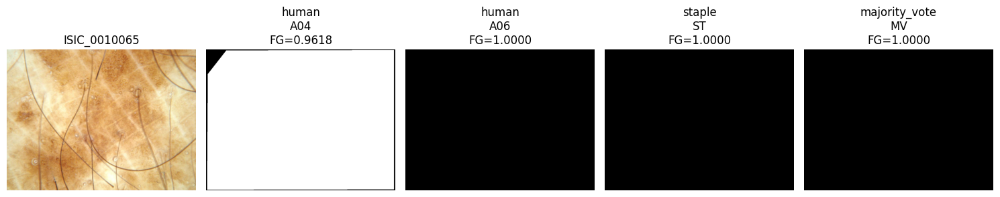

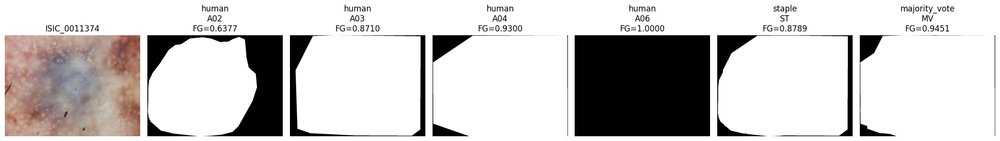

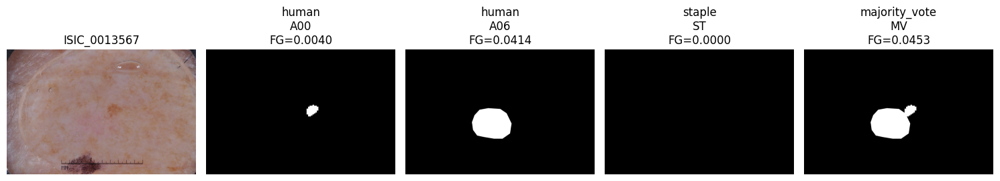

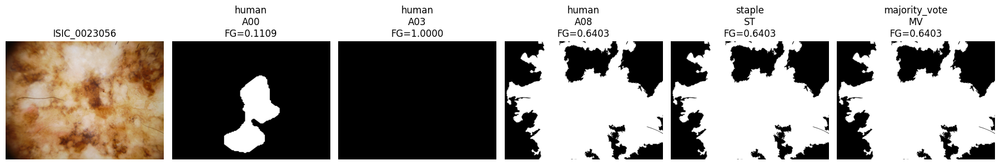

In [ ]:
import json
import matplotlib.pyplot as plt

affected_ids = sorted(
    problem_details["isic_id"].unique()
)

for isic_id in affected_ids:
    index_row = multi_index[
        multi_index["isic_id"] == isic_id
    ].iloc[0]

    source_masks = (
        json.loads(index_row["human_mask_paths"])
        + [index_row["staple_mask_path"]]
        + [index_row["majority_mask_path"]]
    )

    image_path = local_image_map[
        Path(index_row["image_path"]).name.lower()
    ]

    mask_paths_for_image = [
        local_mask_map[Path(path).name.lower()]
        for path in source_masks
    ]

    with Image.open(image_path) as image:
        image_array = np.asarray(image.convert("RGB"))

    number_of_panels = 1 + len(mask_paths_for_image)

    figure, axes = plt.subplots(
        1,
        number_of_panels,
        figsize=(3 * number_of_panels, 3),
    )

    axes[0].imshow(image_array)
    axes[0].set_title(isic_id)
    axes[0].axis("off")

    for axis, mask_path in zip(
        axes[1:],
        mask_paths_for_image,
    ):
        with Image.open(mask_path) as mask:
            mask_array = np.asarray(
                mask.convert("L")
            )

        foreground = (mask_array > 0).mean()

        matching = official_manifest[
            official_manifest["seg_filename"]
            .str.lower()
            .eq(mask_path.name.lower())
        ].iloc[0]

        axis.imshow(mask_array, cmap="gray")
        axis.set_title(
            f"{matching['mask_type']}\n"
            f"{matching['annotator']}\n"
            f"FG={foreground:.4f}"
        )
        axis.axis("off")

    plt.tight_layout()
    plt.show()

In [ ]:
# Convert audit flags to proper nullable Boolean columns
boolean_columns = [
    "mask_empty",
    "mask_full",
    "is_degenerate_mask",
    "boundary_target_valid",
    "mask_audit_available",
]

for column in boolean_columns:
    manifest[column] = manifest[column].astype("boolean")

official_mask_rows = manifest[
    manifest["split"].isin(
        ["train", "validation", "test"]
    )
].copy()

# Validate using explicit True/False comparisons
empty_count = (
    official_mask_rows["mask_empty"]
    .eq(True)
    .sum()
)

full_count = (
    official_mask_rows["mask_full"]
    .eq(True)
    .sum()
)

degenerate_count = (
    official_mask_rows["is_degenerate_mask"]
    .eq(True)
    .sum()
)

boundary_invalid_count = (
    official_mask_rows["boundary_target_valid"]
    .eq(False)
    .sum()
)

boundary_valid_count = (
    official_mask_rows["boundary_target_valid"]
    .eq(True)
    .sum()
)

print("Official masks audited:", len(official_mask_rows))
print("Empty masks:", empty_count)
print("Full masks:", full_count)
print("Degenerate masks:", degenerate_count)
print("Boundary-valid masks:", boundary_valid_count)
print("Boundary-invalid masks:", boundary_invalid_count)

assert len(official_mask_rows) == 9899
assert official_mask_rows[
    "mask_audit_available"
].eq(True).all()

assert empty_count == 1
assert full_count == 5
assert degenerate_count == 6
assert boundary_valid_count == 9893
assert boundary_invalid_count == 6

degenerate_manifest = official_mask_rows[
    official_mask_rows["is_degenerate_mask"].eq(True)
].copy()

assert degenerate_manifest["isic_id"].nunique() == 4

# Save after validation
manifest.to_csv(
    AUDIT_OUTPUT / "canonical_manifest.csv",
    index=False,
)

degenerate_manifest.to_csv(
    AUDIT_OUTPUT / "degenerate_mask_manifest.csv",
    index=False,
)

display(
    degenerate_manifest[
        [
            "isic_id",
            "split",
            "mask_type",
            "annotator",
            "mask_empty",
            "mask_full",
            "boundary_target_valid",
            "seg_filename",
        ]
    ]
)

print("\nCanonical manifest repaired, validated, and saved.")

Official masks audited: 9899
Empty masks: 1
Full masks: 5
Degenerate masks: 6
Boundary-valid masks: 9893
Boundary-invalid masks: 6


,isic_id,split,mask_type,annotator,mask_empty,mask_full,boundary_target_valid,seg_filename
11113,ISIC_0010065,train,human,A06,False,True,False,ISIC_0010065_A06_T3_S1_568bbb5f9fc3c126c063ff8...
12603,ISIC_0011374,train,human,A06,False,True,False,ISIC_0011374_A06_T3_S1_568bbae79fc3c126c063ff7...
17111,ISIC_0023056,train,human,A03,False,True,False,ISIC_0023056_A03_T3_S1_5b3020c211659747a0a010e...
19698,ISIC_0010065,train,staple,ST,False,True,False,ISIC_0010065_ST_ST_ST_ST.png
19699,ISIC_0010065,train,majority_vote,MV,False,True,False,ISIC_0010065_MV_MV_MV_MV.png
20782,ISIC_0013567,train,staple,ST,True,False,False,ISIC_0013567_ST_ST_ST_ST.png



Canonical manifest repaired, validated, and saved.


# Cell 1 — Target functions

In [ ]:
import json
import numpy as np
from pathlib import Path
from PIL import Image
from scipy import ndimage

TARGET_HEIGHT = 352
TARGET_WIDTH = 352
BOUNDARY_RADIUS = 2
ENTROPY_EPSILON = 1e-7

def load_binary_mask(path, size=(TARGET_WIDTH, TARGET_HEIGHT)):
    with Image.open(path) as mask:
        mask = mask.convert("L")
        mask = mask.resize(
            size,
            resample=Image.Resampling.NEAREST,
        )
        array = np.asarray(mask)

    return (array > 0).astype(np.float32)

def normalized_binary_entropy(
    probability,
    epsilon=ENTROPY_EPSILON,
):
    probability = np.asarray(
        probability,
        dtype=np.float32,
    )

    result = np.zeros_like(
        probability,
        dtype=np.float32,
    )

    uncertain = (
        (probability > 0.0)
        & (probability < 1.0)
    )

    p = np.clip(
        probability[uncertain],
        epsilon,
        1.0 - epsilon,
    )

    result[uncertain] = -(
        p * np.log2(p)
        + (1.0 - p) * np.log2(1.0 - p)
    )

    return result

def boundary_band(binary_mask, radius=BOUNDARY_RADIUS):
    mask = binary_mask.astype(bool)

    # Empty and full masks have no usable internal boundary
    if not mask.any() or mask.all():
        return np.zeros_like(
            binary_mask,
            dtype=np.float32,
        )

    eroded = ndimage.binary_erosion(
        mask,
        iterations=1,
        border_value=0,
    )

    inner_boundary = mask & (~eroded)

    if radius > 0:
        inner_boundary = ndimage.binary_dilation(
            inner_boundary,
            iterations=radius,
        )

    return inner_boundary.astype(np.float32)

def construct_targets(index_row):
    source_human_paths = json.loads(
        index_row["human_mask_paths"]
    )

    local_human_paths = [
        local_mask_map[
            Path(path).name.lower()
        ]
        for path in source_human_paths
    ]

    human_stack = np.stack(
        [
            load_binary_mask(path)
            for path in local_human_paths
        ],
        axis=0,
    )

    number_of_masks = human_stack.shape[0]

    soft_consensus = human_stack.mean(
        axis=0,
        dtype=np.float32,
    )

    human_disagreement = normalized_binary_entropy(
        soft_consensus
    )

    # This is a thresholded soft consensus, not the
    # provided majority-vote mask.
    hard_consensus = (
        soft_consensus >= 0.5
    ).astype(np.float32)

    human_boundaries = np.stack(
        [
            boundary_band(mask)
            for mask in human_stack
        ],
        axis=0,
    )

    valid_boundary_mask = np.array(
        [
            mask.any() and not mask.all()
            for mask in human_stack
        ],
        dtype=bool,
    )

    if valid_boundary_mask.any():
        boundary_probability = (
            human_boundaries[valid_boundary_mask]
            .mean(axis=0, dtype=np.float32)
        )
    else:
        boundary_probability = np.zeros_like(
            soft_consensus,
            dtype=np.float32,
        )

    boundary_disagreement = normalized_binary_entropy(
        boundary_probability
    )

    consensus_boundary = boundary_band(
        hard_consensus
    )

    targets = {
        "human_stack": human_stack,
        "soft_consensus": soft_consensus,
        "human_disagreement": human_disagreement,
        "hard_consensus": hard_consensus,
        "human_boundaries": human_boundaries,
        "boundary_probability": boundary_probability,
        "boundary_disagreement":
            boundary_disagreement,
        "consensus_boundary": consensus_boundary,
        "num_human_masks": number_of_masks,
        "num_valid_boundary_masks": int(
            valid_boundary_mask.sum()
        ),
        "valid_boundary_mask": valid_boundary_mask,
    }

    # Numerical validation
    assert human_stack.shape == (
        number_of_masks,
        TARGET_HEIGHT,
        TARGET_WIDTH,
    )

    for name in [
        "soft_consensus",
        "human_disagreement",
        "hard_consensus",
        "boundary_probability",
        "boundary_disagreement",
        "consensus_boundary",
    ]:
        value = targets[name]

        assert value.shape == (
            TARGET_HEIGHT,
            TARGET_WIDTH,
        )

        assert np.isfinite(value).all()
        assert value.min() >= 0.0
        assert value.max() <= 1.0

    return targets

print("Target-construction functions defined.")

Target-construction functions defined.


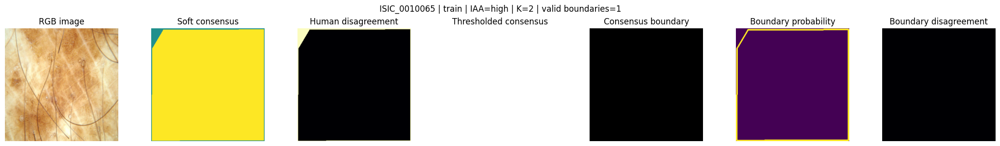

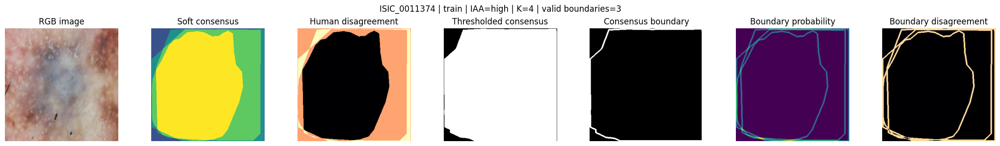

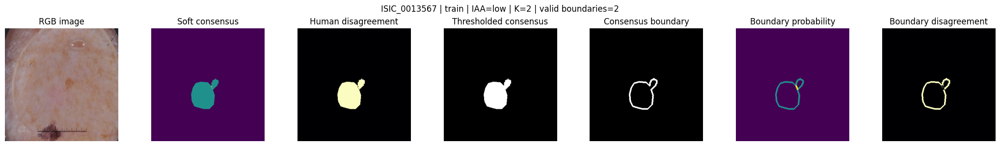

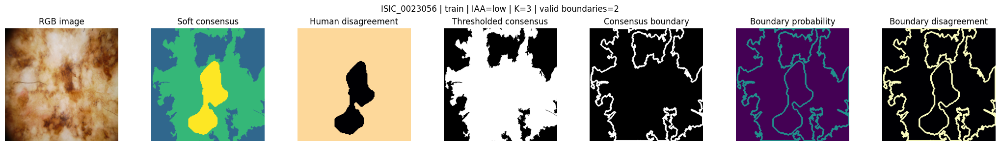

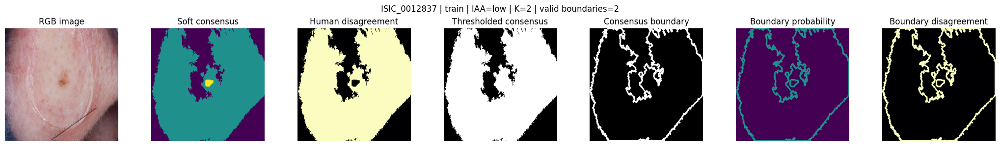

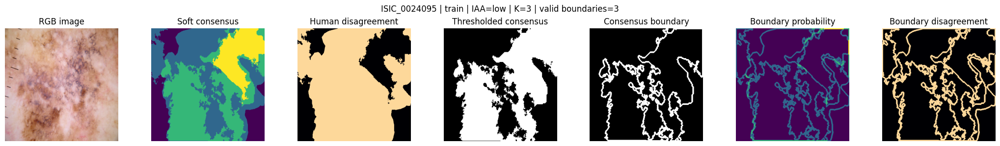

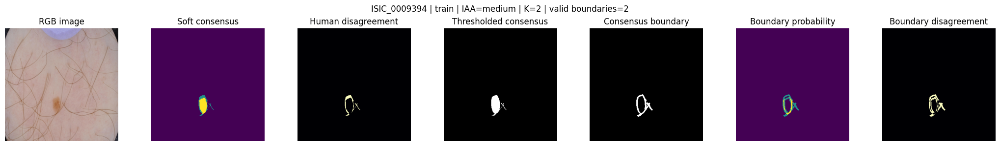

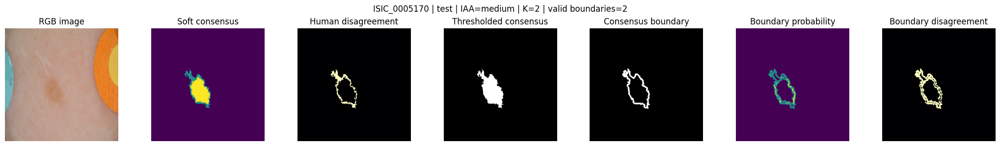

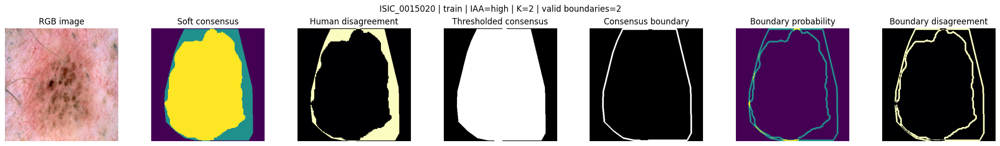

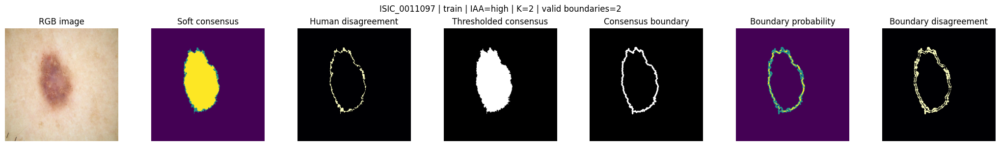

,isic_id,split,iaa_group,num_human_masks,num_valid_boundary_masks,soft_min,soft_max,disagreement_max,boundary_disagreement_max
0,ISIC_0010065,train,high,2,1,0.500000,1.0,1.000000,0.000000
1,ISIC_0011374,train,high,4,3,0.250000,1.0,1.000000,0.918296
2,ISIC_0013567,train,low,2,2,0.000000,1.0,1.000000,1.000000
3,ISIC_0023056,train,low,3,2,0.333333,1.0,0.918296,1.000000
4,ISIC_0012837,train,low,2,2,0.000000,1.0,1.000000,1.000000
5,ISIC_0024095,train,low,3,3,0.000000,1.0,0.918296,0.918296
6,ISIC_0009394,train,medium,2,2,0.000000,1.0,1.000000,1.000000
7,ISIC_0005170,test,medium,2,2,0.000000,1.0,1.000000,1.000000
8,ISIC_0015020,train,high,2,2,0.000000,1.0,1.000000,1.000000
9,ISIC_0011097,train,high,2,2,0.000000,1.0,1.000000,1.000000


Initial target validation completed.


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

anomaly_ids = [
    "ISIC_0010065",
    "ISIC_0011374",
    "ISIC_0013567",
    "ISIC_0023056",
]

normal_examples = []

for iaa_group in ["low", "medium", "high"]:
    candidates = multi_index[
        (multi_index["iaa_group"] == iaa_group)
        & (~multi_index["isic_id"].isin(anomaly_ids))
    ]

    normal_examples.extend(
        candidates.sample(
            n=2,
            random_state=42,
        )["isic_id"].tolist()
    )

selected_ids = anomaly_ids + normal_examples
validation_records = []

for isic_id in selected_ids:
    row = multi_index[
        multi_index["isic_id"] == isic_id
    ].iloc[0]

    targets = construct_targets(row)

    image_path = local_image_map[
        Path(row["image_path"]).name.lower()
    ]

    with Image.open(image_path) as image:
        image = image.convert("RGB")
        image = image.resize(
            (TARGET_WIDTH, TARGET_HEIGHT),
            resample=Image.Resampling.BILINEAR,
        )
        image_array = np.asarray(image)

    validation_records.append({
        "isic_id": isic_id,
        "split": row["split"],
        "iaa_group": row["iaa_group"],
        "num_human_masks":
            targets["num_human_masks"],
        "num_valid_boundary_masks":
            targets["num_valid_boundary_masks"],
        "soft_min":
            float(targets["soft_consensus"].min()),
        "soft_max":
            float(targets["soft_consensus"].max()),
        "disagreement_max":
            float(targets["human_disagreement"].max()),
        "boundary_disagreement_max":
            float(
                targets["boundary_disagreement"].max()
            ),
    })

    panels = [
        ("RGB image", image_array, None),
        (
            "Soft consensus",
            targets["soft_consensus"],
            "viridis",
        ),
        (
            "Human disagreement",
            targets["human_disagreement"],
            "magma",
        ),
        (
            "Thresholded consensus",
            targets["hard_consensus"],
            "gray",
        ),
        (
            "Consensus boundary",
            targets["consensus_boundary"],
            "gray",
        ),
        (
            "Boundary probability",
            targets["boundary_probability"],
            "viridis",
        ),
        (
            "Boundary disagreement",
            targets["boundary_disagreement"],
            "magma",
        ),
    ]

    figure, axes = plt.subplots(
        1,
        len(panels),
        figsize=(21, 3),
    )

    for axis, (title, panel, cmap) in zip(
        axes,
        panels,
    ):
        if cmap is None:
            axis.imshow(panel)
        else:
            axis.imshow(
                panel,
                cmap=cmap,
                vmin=0,
                vmax=1,
            )

        axis.set_title(title)
        axis.axis("off")

    figure.suptitle(
        f"{isic_id} | {row['split']} | "
        f"IAA={row['iaa_group']} | "
        f"K={targets['num_human_masks']} | "
        f"valid boundaries="
        f"{targets['num_valid_boundary_masks']}"
    )

    plt.tight_layout()
    plt.show()

target_validation = pd.DataFrame(
    validation_records
)

display(target_validation)

target_validation.to_csv(
    AUDIT_OUTPUT / "target_validation_summary.csv",
    index=False,
)

print("Initial target validation completed.")

In [ ]:
from tqdm.auto import tqdm
import pandas as pd
import numpy as np

target_audit_records = []
target_errors = []

for _, row in tqdm(
    multi_index.iterrows(),
    total=len(multi_index),
    desc="Validating all targets",
):
    try:
        targets = construct_targets(row)

        hard_consensus = targets["hard_consensus"]
        disagreement = targets["human_disagreement"]
        boundary_disagreement = (
            targets["boundary_disagreement"]
        )

        target_audit_records.append({
            "isic_id": row["isic_id"],
            "split": row["split"],
            "iaa_group": row["iaa_group"],
            "num_human_masks":
                targets["num_human_masks"],
            "num_valid_boundary_masks":
                targets["num_valid_boundary_masks"],
            "num_invalid_boundary_masks": (
                targets["num_human_masks"]
                - targets["num_valid_boundary_masks"]
            ),
            "soft_consensus_mean": float(
                targets["soft_consensus"].mean()
            ),
            "human_disagreement_mean": float(
                disagreement.mean()
            ),
            "human_disagreement_max": float(
                disagreement.max()
            ),
            "human_disagreement_nonzero_fraction": float(
                (disagreement > 0).mean()
            ),
            "boundary_probability_mean": float(
                targets["boundary_probability"].mean()
            ),
            "boundary_disagreement_mean": float(
                boundary_disagreement.mean()
            ),
            "boundary_disagreement_max": float(
                boundary_disagreement.max()
            ),
            "hard_consensus_empty": bool(
                hard_consensus.max() == 0
            ),
            "hard_consensus_full": bool(
                hard_consensus.min() > 0
            ),
        })

    except Exception as error:
        target_errors.append({
            "isic_id": row["isic_id"],
            "error": repr(error),
        })

target_audit = pd.DataFrame(
    target_audit_records
)

target_errors_df = pd.DataFrame(
    target_errors
)

print("\nFULL TARGET AUDIT")
print("Images expected:", len(multi_index))
print("Images validated:", len(target_audit))
print("Errors:", len(target_errors_df))
print(
    "Images containing invalid human boundaries:",
    (target_audit[
        "num_invalid_boundary_masks"
    ] > 0).sum(),
)
print(
    "Total invalid human boundaries:",
    target_audit[
        "num_invalid_boundary_masks"
    ].sum(),
)
print(
    "Empty thresholded consensuses:",
    target_audit[
        "hard_consensus_empty"
    ].sum(),
)
print(
    "Full thresholded consensuses:",
    target_audit[
        "hard_consensus_full"
    ].sum(),
)

print("\nSummary by annotation count K:")
display(
    target_audit.groupby("num_human_masks").agg(
        images=("isic_id", "count"),
        mean_human_disagreement=(
            "human_disagreement_mean",
            "mean",
        ),
        maximum_human_disagreement=(
            "human_disagreement_max",
            "max",
        ),
        mean_boundary_disagreement=(
            "boundary_disagreement_mean",
            "mean",
        ),
    )
)

print("\nSummary by IAA group:")
display(
    target_audit.groupby("iaa_group").agg(
        images=("isic_id", "count"),
        mean_human_disagreement=(
            "human_disagreement_mean",
            "mean",
        ),
        median_human_disagreement=(
            "human_disagreement_mean",
            "median",
        ),
        mean_boundary_disagreement=(
            "boundary_disagreement_mean",
            "mean",
        ),
    ).reindex(["low", "medium", "high"])
)

target_audit.to_csv(
    AUDIT_OUTPUT / "full_target_numerical_audit.csv",
    index=False,
)

target_errors_df.to_csv(
    AUDIT_OUTPUT / "target_construction_errors.csv",
    index=False,
)

assert len(target_audit) == 2394
assert len(target_errors_df) == 0
assert target_audit[
    "num_invalid_boundary_masks"
].sum() == 3

print("\nFull numerical target validation passed.")

Validating all targets:   0%|          | 0/2394 [00:00<?, ?it/s]


FULL TARGET AUDIT
Images expected: 2394
Images validated: 2394
Errors: 0
Images containing invalid human boundaries: 3
Total invalid human boundaries: 3
Empty thresholded consensuses: 0
Full thresholded consensuses: 1

Summary by annotation count K:


,images,mean_human_disagreement,maximum_human_disagreement,mean_boundary_disagreement
num_human_masks,,,,
2,2130,0.067927,1.000000,0.033299
3,209,0.283951,0.918296,0.081473
4,51,0.213507,1.000000,0.093871
5,4,0.316866,0.970951,0.113260



Summary by IAA group:


,images,mean_human_disagreement,median_human_disagreement,mean_boundary_disagreement
iaa_group,,,,
low,236,0.341128,0.314639,0.057580
medium,576,0.120743,0.050793,0.042373
high,1582,0.041803,0.018910,0.034893



Full numerical target validation passed.


In [ ]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

# The ten cases already inspected
initial_ids = [
    "ISIC_0010065",
    "ISIC_0011374",
    "ISIC_0013567",
    "ISIC_0023056",
    "ISIC_0012837",
    "ISIC_0024095",
    "ISIC_0009394",
    "ISIC_0005170",
    "ISIC_0015020",
    "ISIC_0011097",
]

additional_ids = []

def add_unique(values):
    for value in values:
        if (
            value not in initial_ids
            and value not in additional_ids
            and len(additional_ids) < 10
        ):
            additional_ids.append(value)

# Prioritize all rare K=5 cases
add_unique(
    multi_index[
        multi_index["num_human_masks"] == 5
    ]["isic_id"].sort_values().tolist()
)

# Add K=4 cases across IAA groups
for group in ["low", "medium", "high"]:
    candidates = multi_index[
        (multi_index["num_human_masks"] == 4)
        & (multi_index["iaa_group"] == group)
    ]

    if len(candidates):
        add_unique(
            candidates.sample(
                n=min(2, len(candidates)),
                random_state=43,
            )["isic_id"].tolist()
        )

# Add validation/test examples if space remains
for split in ["validation", "test"]:
    for group in ["low", "medium", "high"]:
        candidates = multi_index[
            (multi_index["split"] == split)
            & (multi_index["iaa_group"] == group)
            & (~multi_index["isic_id"].isin(
                initial_ids + additional_ids
            ))
        ]

        if len(candidates):
            add_unique(
                candidates.sample(
                    n=1,
                    random_state=44,
                )["isic_id"].tolist()
            )

# Deterministic fallback
if len(additional_ids) < 10:
    candidates = multi_index[
        ~multi_index["isic_id"].isin(
            initial_ids + additional_ids
        )
    ]

    add_unique(
        candidates.sample(
            n=10 - len(additional_ids),
            random_state=45,
        )["isic_id"].tolist()
    )

assert len(additional_ids) == 10

FIGURE_DIR = (
    DATA_ROOT
    / "audit_results"
    / "target_validation_figures"
)

FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

case_records = []

for isic_id in additional_ids:
    row = multi_index[
        multi_index["isic_id"] == isic_id
    ].iloc[0]

    targets = construct_targets(row)

    image_path = local_image_map[
        Path(row["image_path"]).name.lower()
    ]

    with Image.open(image_path) as image:
        image = image.convert("RGB").resize(
            (TARGET_WIDTH, TARGET_HEIGHT),
            Image.Resampling.BILINEAR,
        )
        image_array = np.asarray(image)

    human_source_paths = json.loads(
        row["human_mask_paths"]
    )

    human_masks = [
        load_binary_mask(
            local_mask_map[
                Path(path).name.lower()
            ]
        )
        for path in human_source_paths
    ]

    staple = load_binary_mask(
        local_mask_map[
            Path(row["staple_mask_path"]).name.lower()
        ]
    )

    majority = load_binary_mask(
        local_mask_map[
            Path(row["majority_mask_path"]).name.lower()
        ]
    )

    input_panels = [
        ("RGB", image_array, None),
    ]

    for index, mask in enumerate(human_masks):
        input_panels.append(
            (f"Human {index + 1}", mask, "gray")
        )

    input_panels.extend([
        ("STAPLE", staple, "gray"),
        ("Majority", majority, "gray"),
    ])

    output_panels = [
        (
            "Soft consensus",
            targets["soft_consensus"],
            "viridis",
        ),
        (
            "Human disagreement",
            targets["human_disagreement"],
            "magma",
        ),
        (
            "Thresholded consensus",
            targets["hard_consensus"],
            "gray",
        ),
        (
            "Consensus boundary",
            targets["consensus_boundary"],
            "gray",
        ),
        (
            "Boundary probability",
            targets["boundary_probability"],
            "viridis",
        ),
        (
            "Boundary disagreement",
            targets["boundary_disagreement"],
            "magma",
        ),
    ]

    column_count = max(
        len(input_panels),
        len(output_panels),
    )

    figure, axes = plt.subplots(
        2,
        column_count,
        figsize=(2.5 * column_count, 6),
    )

    for axis in axes.ravel():
        axis.axis("off")

    for axis, (title, panel, cmap) in zip(
        axes[0],
        input_panels,
    ):
        if cmap is None:
            axis.imshow(panel)
        else:
            axis.imshow(
                panel,
                cmap=cmap,
                vmin=0,
                vmax=1,
            )

        axis.set_title(title)
        axis.axis("off")

    for axis, (title, panel, cmap) in zip(
        axes[1],
        output_panels,
    ):
        axis.imshow(
            panel,
            cmap=cmap,
            vmin=0,
            vmax=1,
        )
        axis.set_title(title)
        axis.axis("off")

    figure.suptitle(
        f"{isic_id} | {row['split']} | "
        f"IAA={row['iaa_group']} | "
        f"K={row['num_human_masks']}"
    )

    plt.tight_layout()

    figure_path = FIGURE_DIR / f"{isic_id}.png"

    figure.savefig(
        figure_path,
        dpi=150,
        bbox_inches="tight",
    )

    plt.show()
    plt.close(figure)

    case_records.append({
        "isic_id": isic_id,
        "split": row["split"],
        "iaa_group": row["iaa_group"],
        "num_human_masks":
            row["num_human_masks"],
        "figure_path": str(figure_path),
    })

visual_validation_cases = pd.DataFrame(
    case_records
)

visual_validation_cases.to_csv(
    AUDIT_OUTPUT
    / "additional_target_validation_cases.csv",
    index=False,
)

print("Additional cases validated:", len(case_records))
print("Total visually inspected cases:", 20)
print("Figures saved to:", FIGURE_DIR)

display(visual_validation_cases)

Output hidden; open in https://colab.research.google.com to view.

# data pipeline




In [ ]:
import json
import random
import numpy as np
import pandas as pd
import torch

from pathlib import Path
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import ColorJitter
from torchvision.transforms.functional import (
    pil_to_tensor,
    normalize,
)

MAX_ANNOTATORS = 5

ANNOTATOR_TO_ID = {
    f"A{index:02d}": index
    for index in range(16)
}

TOOL_TO_ID = {
    "T1": 0,
    "T2": 1,
    "T3": 2,
}

SKILL_TO_ID = {
    "S1": 0,
    "S2": 1,
}

IAA_TO_ID = {
    "low": 0,
    "medium": 1,
    "high": 2,
}

def construct_targets_from_stack(human_stack):
    human_stack = human_stack.astype(
        np.float32
    )

    k = human_stack.shape[0]

    soft_consensus = human_stack.mean(
        axis=0,
        dtype=np.float32,
    )

    human_disagreement = normalized_binary_entropy(
        soft_consensus
    )

    hard_consensus = (
        soft_consensus >= 0.5
    ).astype(np.float32)

    human_boundaries = np.stack(
        [
            boundary_band(mask)
            for mask in human_stack
        ],
        axis=0,
    )

    boundary_valid = np.array(
        [
            mask.any() and not mask.all()
            for mask in human_stack
        ],
        dtype=bool,
    )

    if boundary_valid.any():
        boundary_probability = (
            human_boundaries[boundary_valid]
            .mean(axis=0, dtype=np.float32)
        )
    else:
        boundary_probability = np.zeros_like(
            soft_consensus
        )

    boundary_disagreement = normalized_binary_entropy(
        boundary_probability
    )

    consensus_boundary = boundary_band(
        hard_consensus
    )

    return {
        "soft_consensus": soft_consensus,
        "human_disagreement": human_disagreement,
        "hard_consensus": hard_consensus,
        "human_boundaries": human_boundaries,
        "boundary_valid": boundary_valid,
        "boundary_probability":
            boundary_probability,
        "boundary_disagreement":
            boundary_disagreement,
        "consensus_boundary":
            consensus_boundary,
    }

class MultiAnnotatorDataset(Dataset):
    def __init__(
        self,
        index_frame,
        local_image_dir,
        local_mask_dir,
        augment=False,
    ):
        self.frame = (
            index_frame
            .reset_index(drop=True)
            .copy()
        )

        self.local_image_dir = Path(
            local_image_dir
        )

        self.local_mask_dir = Path(
            local_mask_dir
        )

        self.augment = augment

        self.color_jitter = ColorJitter(
            brightness=0.15,
            contrast=0.15,
            saturation=0.10,
            hue=0.02,
        )

        self.image_map = {
            path.name.lower(): path
            for path in self.local_image_dir.iterdir()
            if path.is_file()
        }

        self.mask_map = {
            path.name.lower(): path
            for path in self.local_mask_dir.iterdir()
            if path.is_file()
        }

    def __len__(self):
        return len(self.frame)

    def _local_image_path(self, source_path):
        return self.image_map[
            Path(source_path).name.lower()
        ]

    def _local_mask_path(self, source_path):
        return self.mask_map[
            Path(source_path).name.lower()
        ]

    def _load_image(self, source_path):
        path = self._local_image_path(
            source_path
        )

        with Image.open(path) as image:
            image = image.convert("RGB")
            image = image.resize(
                (TARGET_WIDTH, TARGET_HEIGHT),
                Image.Resampling.BILINEAR,
            )
            return np.asarray(image).copy()

    def _load_mask(self, source_path):
        path = self._local_mask_path(
            source_path
        )

        return load_binary_mask(
            path,
            size=(TARGET_WIDTH, TARGET_HEIGHT),
        )

    def _geometric_augmentation(
        self,
        image,
        masks,
    ):
        # Horizontal flip
        if torch.rand(1).item() < 0.5:
            image = np.flip(image, axis=1)
            masks = np.flip(masks, axis=2)

        # Vertical flip
        if torch.rand(1).item() < 0.5:
            image = np.flip(image, axis=0)
            masks = np.flip(masks, axis=1)

        # Rotation by 0, 90, 180, or 270 degrees
        rotations = int(
            torch.randint(0, 4, (1,)).item()
        )

        if rotations:
            image = np.rot90(
                image,
                k=rotations,
                axes=(0, 1),
            )

            masks = np.rot90(
                masks,
                k=rotations,
                axes=(1, 2),
            )

        # Remove negative strides created by flips/rotations
        return image.copy(), masks.copy()

    def __getitem__(self, index):
        row = self.frame.iloc[index]

        image = self._load_image(
            row["image_path"]
        )

        human_source_paths = json.loads(
            row["human_mask_paths"]
        )

        annotators = json.loads(
            row["annotators"]
        )

        tools = json.loads(
            row["tools"]
        )

        skills = json.loads(
            row["skill_levels"]
        )

        human_stack = np.stack(
            [
                self._load_mask(path)
                for path in human_source_paths
            ],
            axis=0,
        )

        staple_mask = self._load_mask(
            row["staple_mask_path"]
        )

        majority_mask = self._load_mask(
            row["majority_mask_path"]
        )

        # Transform all spatial masks together
        combined_masks = np.concatenate(
            [
                human_stack,
                staple_mask[None],
                majority_mask[None],
            ],
            axis=0,
        )

        if self.augment:
            image, combined_masks = (
                self._geometric_augmentation(
                    image,
                    combined_masks,
                )
            )

        k = len(human_source_paths)

        human_stack = combined_masks[:k]
        staple_mask = combined_masks[k]
        majority_mask = combined_masks[k + 1]

        # Construct targets after geometric augmentation
        targets = construct_targets_from_stack(
            human_stack
        )

        # Image-only photometric augmentation
        image_pil = Image.fromarray(
            image.astype(np.uint8)
        )

        if self.augment:
            image_pil = self.color_jitter(
                image_pil
            )

        image_tensor = (
            pil_to_tensor(image_pil)
            .float()
            .div(255.0)
        )

        image_tensor = normalize(
            image_tensor,
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225],
        )

        # Pad variable human masks to K=5
        padded_human_masks = np.zeros(
            (
                MAX_ANNOTATORS,
                TARGET_HEIGHT,
                TARGET_WIDTH,
            ),
            dtype=np.float32,
        )

        padded_boundaries = np.zeros_like(
            padded_human_masks
        )

        mask_valid = np.zeros(
            MAX_ANNOTATORS,
            dtype=bool,
        )

        boundary_valid = np.zeros(
            MAX_ANNOTATORS,
            dtype=bool,
        )

        annotator_ids = np.full(
            MAX_ANNOTATORS,
            -1,
            dtype=np.int64,
        )

        tool_ids = np.full(
            MAX_ANNOTATORS,
            -1,
            dtype=np.int64,
        )

        skill_ids = np.full(
            MAX_ANNOTATORS,
            -1,
            dtype=np.int64,
        )

        padded_human_masks[:k] = human_stack
        padded_boundaries[:k] = targets[
            "human_boundaries"
        ]

        mask_valid[:k] = True
        boundary_valid[:k] = targets[
            "boundary_valid"
        ]

        annotator_ids[:k] = [
            ANNOTATOR_TO_ID[value]
            for value in annotators
        ]

        tool_ids[:k] = [
            TOOL_TO_ID[value]
            for value in tools
        ]

        skill_ids[:k] = [
            SKILL_TO_ID[value]
            for value in skills
        ]

        def spatial_tensor(array):
            return torch.from_numpy(
                array.astype(np.float32)
            ).unsqueeze(0)

        return {
            "image": image_tensor,
            "human_masks": torch.from_numpy(
                padded_human_masks
            ),
            "mask_valid": torch.from_numpy(
                mask_valid
            ),
            "human_boundaries": torch.from_numpy(
                padded_boundaries
            ),
            "boundary_valid": torch.from_numpy(
                boundary_valid
            ),
            "annotator_ids": torch.from_numpy(
                annotator_ids
            ),
            "tool_ids": torch.from_numpy(
                tool_ids
            ),
            "skill_ids": torch.from_numpy(
                skill_ids
            ),
            "soft_consensus": spatial_tensor(
                targets["soft_consensus"]
            ),
            "human_disagreement": spatial_tensor(
                targets["human_disagreement"]
            ),
            "hard_consensus": spatial_tensor(
                targets["hard_consensus"]
            ),
            "consensus_boundary": spatial_tensor(
                targets["consensus_boundary"]
            ),
            "boundary_probability": spatial_tensor(
                targets["boundary_probability"]
            ),
            "boundary_disagreement": spatial_tensor(
                targets["boundary_disagreement"]
            ),
            "staple_mask": spatial_tensor(
                staple_mask
            ),
            "majority_mask": spatial_tensor(
                majority_mask
            ),
            "num_human_masks": torch.tensor(
                k,
                dtype=torch.long,
            ),
            "iaa_id": torch.tensor(
                IAA_TO_ID[row["iaa_group"]],
                dtype=torch.long,
            ),
            "isic_id": row["isic_id"],
            "split": row["split"],
            "iaa_group": row["iaa_group"],
        }

print("MultiAnnotatorDataset defined.")

MultiAnnotatorDataset defined.


In [ ]:
import random
import numpy as np
import torch
from torch.utils.data import DataLoader

GLOBAL_SEED = 42
BATCH_SIZE = 4
NUM_WORKERS = 2

def seed_worker(worker_id):
    worker_seed = (
        torch.initial_seed() % (2 ** 32)
    )

    np.random.seed(worker_seed)
    random.seed(worker_seed)

generator = torch.Generator()
generator.manual_seed(GLOBAL_SEED)

train_frame = multi_index[
    multi_index["split"] == "train"
].reset_index(drop=True)

validation_frame = multi_index[
    multi_index["split"] == "validation"
].reset_index(drop=True)

test_frame = multi_index[
    multi_index["split"] == "test"
].reset_index(drop=True)

assert len(train_frame) == 1675
assert len(validation_frame) == 240
assert len(test_frame) == 479

train_dataset = MultiAnnotatorDataset(
    train_frame,
    LOCAL_IMAGE_DIR,
    LOCAL_MASK_DIR,
    augment=True,
)

validation_dataset = MultiAnnotatorDataset(
    validation_frame,
    LOCAL_IMAGE_DIR,
    LOCAL_MASK_DIR,
    augment=False,
)

test_dataset = MultiAnnotatorDataset(
    test_frame,
    LOCAL_IMAGE_DIR,
    LOCAL_MASK_DIR,
    augment=False,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    worker_init_fn=seed_worker,
    generator=generator,
    persistent_workers=False,
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    worker_init_fn=seed_worker,
    persistent_workers=False,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    worker_init_fn=seed_worker,
    persistent_workers=False,
)

batch = next(iter(train_loader))

print("Batch keys:")
print(list(batch.keys()))

print("\nTensor shapes:")
for key, value in batch.items():
    if torch.is_tensor(value):
        print(
            f"{key:25s}",
            tuple(value.shape),
            value.dtype,
        )

# ---------- Shape validation ----------

assert batch["image"].shape == (
    BATCH_SIZE, 3, 352, 352
)

assert batch["human_masks"].shape == (
    BATCH_SIZE, 5, 352, 352
)

assert batch["mask_valid"].shape == (
    BATCH_SIZE, 5
)

assert batch["human_boundaries"].shape == (
    BATCH_SIZE, 5, 352, 352
)

for key in [
    "soft_consensus",
    "human_disagreement",
    "hard_consensus",
    "consensus_boundary",
    "boundary_probability",
    "boundary_disagreement",
    "staple_mask",
    "majority_mask",
]:
    assert batch[key].shape == (
        BATCH_SIZE, 1, 352, 352
    )

# ---------- Padding validation ----------

observed_k = batch["mask_valid"].sum(dim=1)

assert torch.equal(
    observed_k,
    batch["num_human_masks"],
)

invalid_slots = ~batch["mask_valid"]

assert (
    batch["human_masks"][invalid_slots]
    == 0
).all()

assert (
    batch["annotator_ids"][invalid_slots]
    == -1
).all()

assert (
    batch["tool_ids"][invalid_slots]
    == -1
).all()

assert (
    batch["skill_ids"][invalid_slots]
    == -1
).all()

assert (
    batch["boundary_valid"]
    <= batch["mask_valid"]
).all()

# ---------- Reconstruct consensus ----------

valid_weights = (
    batch["mask_valid"]
    .float()
    .unsqueeze(-1)
    .unsqueeze(-1)
)

reconstructed_consensus = (
    batch["human_masks"]
    * valid_weights
).sum(dim=1) / observed_k.float().view(
    -1, 1, 1
)

assert torch.allclose(
    reconstructed_consensus,
    batch["soft_consensus"][:, 0],
    atol=1e-6,
)

# ---------- Range validation ----------

for key in [
    "human_masks",
    "human_boundaries",
    "soft_consensus",
    "human_disagreement",
    "hard_consensus",
    "consensus_boundary",
    "boundary_probability",
    "boundary_disagreement",
    "staple_mask",
    "majority_mask",
]:
    tensor = batch[key]

    assert torch.isfinite(tensor).all()
    assert tensor.min() >= 0
    assert tensor.max() <= 1

# ---------- Split validation ----------

assert set(batch["split"]) == {"train"}

assert set(train_frame["isic_id"]).isdisjoint(
    validation_frame["isic_id"]
)

assert set(train_frame["isic_id"]).isdisjoint(
    test_frame["isic_id"]
)

assert set(validation_frame["isic_id"]).isdisjoint(
    test_frame["isic_id"]
)

# ---------- Validation determinism ----------

validation_a = validation_dataset[0]
validation_b = validation_dataset[0]

for key, value in validation_a.items():
    if torch.is_tensor(value):
        assert torch.equal(
            value,
            validation_b[key],
        ), f"Non-deterministic validation tensor: {key}"

print("\nDataset sizes:")
print("Train:", len(train_dataset))
print("Validation:", len(validation_dataset))
print("Test:", len(test_dataset))

print("\nBatch image IDs:", batch["isic_id"])
print("Batch annotation counts:", observed_k.tolist())
print("Batch IAA groups:", batch["iaa_group"])

print("\nAll DataLoader validation checks passed.")

Batch keys:
['image', 'human_masks', 'mask_valid', 'human_boundaries', 'boundary_valid', 'annotator_ids', 'tool_ids', 'skill_ids', 'soft_consensus', 'human_disagreement', 'hard_consensus', 'consensus_boundary', 'boundary_probability', 'boundary_disagreement', 'staple_mask', 'majority_mask', 'num_human_masks', 'iaa_id', 'isic_id', 'split', 'iaa_group']

Tensor shapes:
image                     (4, 3, 352, 352) torch.float32
human_masks               (4, 5, 352, 352) torch.float32
mask_valid                (4, 5) torch.bool
human_boundaries          (4, 5, 352, 352) torch.float32
boundary_valid            (4, 5) torch.bool
annotator_ids             (4, 5) torch.int64
tool_ids                  (4, 5) torch.int64
skill_ids                 (4, 5) torch.int64
soft_consensus            (4, 1, 352, 352) torch.float32
human_disagreement        (4, 1, 352, 352) torch.float32
hard_consensus            (4, 1, 352, 352) torch.float32
consensus_boundary        (4, 1, 352, 352) torch.float32
boundary

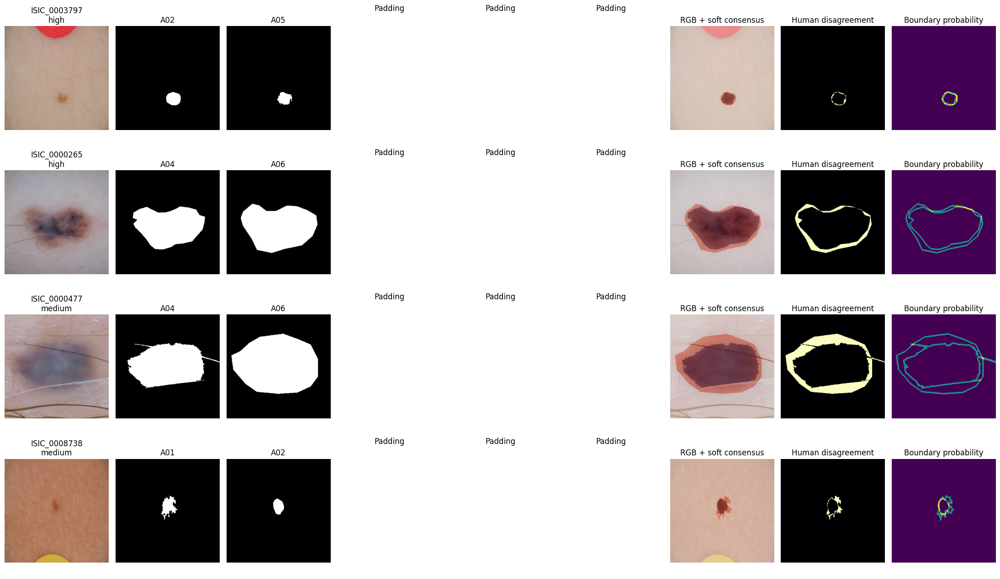

Augmentation figure saved to: /content/drive/MyDrive/MADSeg/audit_results/augmented_batch_validation.png


In [ ]:
import matplotlib.pyplot as plt
import torch
import numpy as np

ID_TO_ANNOTATOR = {
    value: key
    for key, value in ANNOTATOR_TO_ID.items()
}

imagenet_mean = torch.tensor(
    [0.485, 0.456, 0.406]
).view(3, 1, 1)

imagenet_std = torch.tensor(
    [0.229, 0.224, 0.225]
).view(3, 1, 1)

batch_size = batch["image"].shape[0]
columns = 9

figure, axes = plt.subplots(
    batch_size,
    columns,
    figsize=(22, 3.2 * batch_size),
)

if batch_size == 1:
    axes = axes[None, :]

for row_index in range(batch_size):
    image = (
        batch["image"][row_index].cpu()
        * imagenet_std
        + imagenet_mean
    ).clamp(0, 1)

    image = image.permute(
        1, 2, 0
    ).numpy()

    soft = (
        batch["soft_consensus"][
            row_index, 0
        ].cpu().numpy()
    )

    disagreement = (
        batch["human_disagreement"][
            row_index, 0
        ].cpu().numpy()
    )

    boundary = (
        batch["boundary_probability"][
            row_index, 0
        ].cpu().numpy()
    )

    # RGB
    axes[row_index, 0].imshow(image)
    axes[row_index, 0].set_title(
        f"{batch['isic_id'][row_index]}\n"
        f"{batch['iaa_group'][row_index]}"
    )

    # Up to five original human masks
    for mask_index in range(MAX_ANNOTATORS):
        axis = axes[
            row_index,
            1 + mask_index,
        ]

        if batch["mask_valid"][
            row_index,
            mask_index,
        ]:
            mask = batch["human_masks"][
                row_index,
                mask_index,
            ].cpu().numpy()

            annotator_id = int(
                batch["annotator_ids"][
                    row_index,
                    mask_index,
                ]
            )

            axis.imshow(
                mask,
                cmap="gray",
                vmin=0,
                vmax=1,
            )

            axis.set_title(
                ID_TO_ANNOTATOR[
                    annotator_id
                ]
            )
        else:
            axis.set_title("Padding")

    # Consensus overlay
    axes[row_index, 6].imshow(image)
    axes[row_index, 6].imshow(
        soft,
        cmap="Reds",
        alpha=0.45,
        vmin=0,
        vmax=1,
    )
    axes[row_index, 6].set_title(
        "RGB + soft consensus"
    )

    axes[row_index, 7].imshow(
        disagreement,
        cmap="magma",
        vmin=0,
        vmax=1,
    )
    axes[row_index, 7].set_title(
        "Human disagreement"
    )

    axes[row_index, 8].imshow(
        boundary,
        cmap="viridis",
        vmin=0,
        vmax=1,
    )
    axes[row_index, 8].set_title(
        "Boundary probability"
    )

    for column_index in range(columns):
        axes[row_index, column_index].axis(
            "off"
        )

plt.tight_layout()

AUGMENTATION_FIGURE = (
    AUDIT_OUTPUT / "augmented_batch_validation.png"
)

figure.savefig(
    AUGMENTATION_FIGURE,
    dpi=160,
    bbox_inches="tight",
)

plt.show()
plt.close(figure)

print(
    "Augmentation figure saved to:",
    AUGMENTATION_FIGURE,
)

In [ ]:
import shutil
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm.auto import tqdm
import pandas as pd

PRETRAIN_MANIFEST_PATH = (
    AUDIT_OUTPUT / "pretraining_manifest.csv"
)

pretraining_manifest = pd.read_csv(
    PRETRAIN_MANIFEST_PATH
)

assert len(pretraining_manifest) == 12390
assert pretraining_manifest["isic_id"].is_unique
assert pretraining_manifest[
    "image_path"
].notna().all()

assert pretraining_manifest[
    "mask_path"
].notna().all()

free_before_gb = (
    shutil.disk_usage("/content").free
    / (1024 ** 3)
)

print(
    f"Free local storage before copy: "
    f"{free_before_gb:.2f} GB"
)

pretraining_copy_tasks = {}

for row in pretraining_manifest.itertuples(
    index=False
):
    image_source = Path(row.image_path)
    mask_source = Path(row.mask_path)

    pretraining_copy_tasks[
        f"image::{image_source}"
    ] = (
        image_source,
        LOCAL_IMAGE_DIR / image_source.name,
    )

    pretraining_copy_tasks[
        f"mask::{mask_source}"
    ] = (
        mask_source,
        LOCAL_MASK_DIR / mask_source.name,
    )

print(
    "Files required for pretraining:",
    len(pretraining_copy_tasks),
)

assert len(pretraining_copy_tasks) == 24780

pretrain_copy_results = {
    "copied": 0,
    "skipped": 0,
    "failed": 0,
}

pretrain_copy_failures = []

with ThreadPoolExecutor(max_workers=8) as executor:
    futures = {
        executor.submit(
            copy_verified,
            task,
        ): task
        for task in pretraining_copy_tasks.values()
    }

    for future in tqdm(
        as_completed(futures),
        total=len(futures),
        desc="Staging pretraining data",
    ):
        source, destination = futures[future]

        try:
            status = future.result()
            pretrain_copy_results[status] += 1

        except Exception as error:
            pretrain_copy_results["failed"] += 1

            pretrain_copy_failures.append({
                "source": str(source),
                "destination": str(destination),
                "error": repr(error),
            })

print("\nCopy results:")
print(pretrain_copy_results)

if pretrain_copy_failures:
    print("\nFirst failures:")

    for failure in pretrain_copy_failures[:10]:
        print(failure)

local_images = [
    path for path in LOCAL_IMAGE_DIR.iterdir()
    if path.is_file()
    and not path.name.endswith(".part")
]

local_masks = [
    path for path in LOCAL_MASK_DIR.iterdir()
    if path.is_file()
    and not path.name.endswith(".part")
]

free_after_gb = (
    shutil.disk_usage("/content").free
    / (1024 ** 3)
)

print("\nTotal locally staged RGB images:", len(local_images))
print("Total locally staged masks:", len(local_masks))
print(
    f"Free local storage after copy: "
    f"{free_after_gb:.2f} GB"
)

assert pretrain_copy_results["failed"] == 0

# Multi-annotator + eligible pretraining pool
assert len(local_images) == 2394 + 12390
assert len(local_masks) == 9899 + 12390

staging_summary = pd.DataFrame([{
    "pretraining_images": 12390,
    "pretraining_masks": 12390,
    "files_copied":
        pretrain_copy_results["copied"],
    "files_skipped":
        pretrain_copy_results["skipped"],
    "files_failed":
        pretrain_copy_results["failed"],
    "total_local_images":
        len(local_images),
    "total_local_masks":
        len(local_masks),
    "free_before_gb": free_before_gb,
    "free_after_gb": free_after_gb,
}])

staging_summary.to_csv(
    AUDIT_OUTPUT
    / "pretraining_local_staging_summary.csv",
    index=False,
)

print(
    "\nPretraining data staged successfully."
)

Free local storage before copy: 201.86 GB
Files required for pretraining: 24780


Staging pretraining data:   0%|          | 0/24780 [00:00<?, ?it/s]


Copy results:
{'copied': 24780, 'skipped': 0, 'failed': 0}

Total locally staged RGB images: 14784
Total locally staged masks: 22289
Free local storage after copy: 190.95 GB

Pretraining data staged successfully.


In [ ]:
class SingleAnnotatorDataset(Dataset):
    def __init__(
        self,
        manifest_frame,
        local_image_dir,
        local_mask_dir,
        augment=False,
    ):
        self.frame = (
            manifest_frame
            .reset_index(drop=True)
            .copy()
        )

        self.augment = augment

        self.image_map = {
            path.name.lower(): path
            for path in Path(
                local_image_dir
            ).iterdir()
            if path.is_file()
        }

        self.mask_map = {
            path.name.lower(): path
            for path in Path(
                local_mask_dir
            ).iterdir()
            if path.is_file()
        }

        self.color_jitter = ColorJitter(
            brightness=0.15,
            contrast=0.15,
            saturation=0.10,
            hue=0.02,
        )

    def __len__(self):
        return len(self.frame)

    def _load_image(self, source_path):
        local_path = self.image_map[
            Path(source_path).name.lower()
        ]

        with Image.open(local_path) as image:
            image = image.convert("RGB")
            image = image.resize(
                (TARGET_WIDTH, TARGET_HEIGHT),
                Image.Resampling.BILINEAR,
            )

            return np.asarray(image).copy()

    def _load_mask(self, source_path):
        local_path = self.mask_map[
            Path(source_path).name.lower()
        ]

        return load_binary_mask(
            local_path,
            size=(TARGET_WIDTH, TARGET_HEIGHT),
        )

    def _geometric_augmentation(
        self,
        image,
        mask,
    ):
        if torch.rand(1).item() < 0.5:
            image = np.flip(image, axis=1)
            mask = np.flip(mask, axis=1)

        if torch.rand(1).item() < 0.5:
            image = np.flip(image, axis=0)
            mask = np.flip(mask, axis=0)

        rotations = int(
            torch.randint(0, 4, (1,)).item()
        )

        if rotations:
            image = np.rot90(
                image,
                k=rotations,
                axes=(0, 1),
            )

            mask = np.rot90(
                mask,
                k=rotations,
                axes=(0, 1),
            )

        return image.copy(), mask.copy()

    def __getitem__(self, index):
        row = self.frame.iloc[index]

        image = self._load_image(
            row["image_path"]
        )

        mask = self._load_mask(
            row["mask_path"]
        )

        if self.augment:
            image, mask = (
                self._geometric_augmentation(
                    image,
                    mask,
                )
            )

        boundary = boundary_band(mask)

        image_pil = Image.fromarray(
            image.astype(np.uint8)
        )

        if self.augment:
            image_pil = self.color_jitter(
                image_pil
            )

        image_tensor = (
            pil_to_tensor(image_pil)
            .float()
            .div(255.0)
        )

        image_tensor = normalize(
            image_tensor,
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225],
        )

        annotator = str(
            row["annotator"]
        ).strip()

        tool = str(
            row["tool"]
        ).strip()

        skill = str(
            row["skill_level"]
        ).strip()

        return {
            "image": image_tensor,
            "target": torch.from_numpy(
                mask.astype(np.float32)
            ).unsqueeze(0),
            "boundary": torch.from_numpy(
                boundary.astype(np.float32)
            ).unsqueeze(0),
            "annotator_id": torch.tensor(
                ANNOTATOR_TO_ID[annotator],
                dtype=torch.long,
            ),
            "tool_id": torch.tensor(
                TOOL_TO_ID[tool],
                dtype=torch.long,
            ),
            "skill_id": torch.tensor(
                SKILL_TO_ID[skill],
                dtype=torch.long,
            ),
            "isic_id": row["isic_id"],
        }

pretrain_dataset = SingleAnnotatorDataset(
    pretraining_manifest,
    LOCAL_IMAGE_DIR,
    LOCAL_MASK_DIR,
    augment=True,
)

pretrain_loader = DataLoader(
    pretrain_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    worker_init_fn=seed_worker,
    generator=generator,
    persistent_workers=False,
)

pretrain_batch = next(
    iter(pretrain_loader)
)

print("Pretraining dataset:", len(pretrain_dataset))

for key, value in pretrain_batch.items():
    if torch.is_tensor(value):
        print(
            f"{key:15s}",
            tuple(value.shape),
            value.dtype,
        )

assert len(pretrain_dataset) == 12390

assert pretrain_batch["image"].shape == (
    BATCH_SIZE, 3, 352, 352
)

assert pretrain_batch["target"].shape == (
    BATCH_SIZE, 1, 352, 352
)

assert pretrain_batch["boundary"].shape == (
    BATCH_SIZE, 1, 352, 352
)

assert torch.isfinite(
    pretrain_batch["image"]
).all()

assert pretrain_batch["target"].min() >= 0
assert pretrain_batch["target"].max() <= 1
assert pretrain_batch["boundary"].min() >= 0
assert pretrain_batch["boundary"].max() <= 1

assert not (
    set(pretraining_manifest["isic_id"])
    & set(validation_frame["isic_id"])
)

assert not (
    set(pretraining_manifest["isic_id"])
    & set(test_frame["isic_id"])
)

print(
    "\nPretraining image IDs:",
    pretrain_batch["isic_id"],
)

print(
    "Annotator IDs:",
    pretrain_batch["annotator_id"].tolist(),
)

print(
    "\nSingle-annotator Dataset validation passed."
)

Pretraining dataset: 12390
image           (4, 3, 352, 352) torch.float32
target          (4, 1, 352, 352) torch.float32
boundary        (4, 1, 352, 352) torch.float32
annotator_id    (4,) torch.int64
tool_id         (4,) torch.int64
skill_id        (4,) torch.int64

Pretraining image IDs: ['ISIC_0001300', 'ISIC_0005479', 'ISIC_0014432', 'ISIC_0002954']
Annotator IDs: [4, 2, 3, 2]

Single-annotator Dataset validation passed.


In [ ]:
from collections import Counter
from torch.utils.data import WeightedRandomSampler
import numpy as np
import pandas as pd
import torch
import json

# Count annotations in training images only
train_annotator_frequency = Counter()

for value in train_frame["annotators"]:
    train_annotator_frequency.update(
        json.loads(value)
    )

print("Training annotator frequencies:")
print(
    pd.Series(
        train_annotator_frequency
    ).sort_values(ascending=False)
)

# Inverse-square-root weighting is less extreme than
# direct inverse-frequency weighting.
raw_weights = []

for value in train_frame["annotators"]:
    sample_annotators = json.loads(value)

    annotator_weights = [
        1.0 / np.sqrt(
            train_annotator_frequency[annotator]
        )
        for annotator in sample_annotators
    ]

    raw_weights.append(
        float(np.mean(annotator_weights))
    )

raw_weights = np.asarray(
    raw_weights,
    dtype=np.float64,
)

# Cap rare-annotator influence
weight_cap = 4.0 * np.median(raw_weights)

capped_weights = np.minimum(
    raw_weights,
    weight_cap,
)

# Normalize to mean weight 1
capped_weights = (
    capped_weights
    / capped_weights.mean()
)

train_sampling_weights = torch.tensor(
    capped_weights,
    dtype=torch.double,
)

sampler_generator = torch.Generator()
sampler_generator.manual_seed(GLOBAL_SEED)

balanced_sampler = WeightedRandomSampler(
    weights=train_sampling_weights,
    num_samples=len(train_frame),
    replacement=True,
    generator=sampler_generator,
)

balanced_train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=balanced_sampler,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    worker_init_fn=seed_worker,
    persistent_workers=False,
)

weight_table = pd.DataFrame({
    "isic_id": train_frame["isic_id"],
    "sampling_weight": capped_weights,
    "annotators": train_frame["annotators"],
    "iaa_group": train_frame["iaa_group"],
    "num_human_masks":
        train_frame["num_human_masks"],
})

weight_table.to_csv(
    AUDIT_OUTPUT
    / "annotator_balanced_sampling_weights.csv",
    index=False,
)

print("\nSampling-weight summary:")
print(weight_table["sampling_weight"].describe())

print(
    "Maximum/median weight ratio:",
    weight_table["sampling_weight"].max()
    / weight_table["sampling_weight"].median(),
)

# ---------- Simulate one balanced epoch ----------

simulated_indices = list(
    iter(balanced_sampler)
)

sampled_annotator_frequency = Counter()

for index in simulated_indices:
    sampled_annotator_frequency.update(
        json.loads(
            train_frame.iloc[index][
                "annotators"
            ]
        )
    )

sampling_comparison = pd.DataFrame({
    "ordinary_frequency":
        pd.Series(train_annotator_frequency),
    "balanced_epoch_frequency":
        pd.Series(sampled_annotator_frequency),
}).fillna(0).astype(int)

sampling_comparison["frequency_ratio"] = (
    sampling_comparison[
        "balanced_epoch_frequency"
    ]
    / sampling_comparison[
        "ordinary_frequency"
    ]
)

display(
    sampling_comparison.sort_values(
        "ordinary_frequency",
        ascending=False,
    )
)

sampling_comparison.to_csv(
    AUDIT_OUTPUT
    / "balanced_sampler_simulated_epoch.csv"
)

# ---------- Final stress test ----------

def validate_multi_batch(current_batch):
    batch_size = current_batch[
        "image"
    ].shape[0]

    assert current_batch["image"].shape == (
        batch_size, 3, 352, 352
    )

    assert current_batch[
        "human_masks"
    ].shape == (
        batch_size, 5, 352, 352
    )

    observed_k = current_batch[
        "mask_valid"
    ].sum(dim=1)

    assert torch.equal(
        observed_k,
        current_batch["num_human_masks"],
    )

    assert torch.isfinite(
        current_batch["image"]
    ).all()

    for key in [
        "human_masks",
        "soft_consensus",
        "human_disagreement",
        "boundary_probability",
        "boundary_disagreement",
        "staple_mask",
        "majority_mask",
    ]:
        value = current_batch[key]

        assert torch.isfinite(value).all()
        assert value.min() >= 0
        assert value.max() <= 1

def validate_pretrain_batch(current_batch):
    batch_size = current_batch[
        "image"
    ].shape[0]

    assert current_batch["image"].shape == (
        batch_size, 3, 352, 352
    )

    assert current_batch["target"].shape == (
        batch_size, 1, 352, 352
    )

    assert torch.isfinite(
        current_batch["image"]
    ).all()

    assert (
        current_batch["target"].min() >= 0
    )

    assert (
        current_batch["target"].max() <= 1
    )

stress_results = {}

for loader_name, loader in [
    ("ordinary_train", train_loader),
    ("balanced_train", balanced_train_loader),
    ("validation", validation_loader),
    ("test", test_loader),
]:
    batches_checked = 0

    for current_batch in loader:
        validate_multi_batch(current_batch)
        batches_checked += 1

        if batches_checked == 8:
            break

    stress_results[loader_name] = batches_checked

pretrain_batches_checked = 0

for current_batch in pretrain_loader:
    validate_pretrain_batch(current_batch)
    pretrain_batches_checked += 1

    if pretrain_batches_checked == 8:
        break

stress_results[
    "single_annotator_pretraining"
] = pretrain_batches_checked

print("\nStress-test results:")
print(stress_results)

assert all(
    value == 8
    for value in stress_results.values()
)

print("\nFinal data-pipeline stress test passed.")
print(
    "Ordinary shuffle remains the default "
    "for baseline experiments."
)
print(
    "Balanced sampling will be tested only "
    "as a controlled MAD-Seg ablation."
)

Training annotator frequencies:
A00    861
A03    672
A01    425
A06    418
A04    382
A02    357
A05    291
A08     92
A09     51
A07      7
A10      6
A11      6
A12      1
A14      1
A15      1
dtype: int64

Sampling-weight summary:
count    1675.000000
mean        1.000000
std         0.397870
min         0.694744
25%         0.740570
50%         1.020062
75%         1.078928
max         4.080248
Name: sampling_weight, dtype: float64
Maximum/median weight ratio: 4.0


,ordinary_frequency,balanced_epoch_frequency,frequency_ratio
A00,861,705,0.818815
A03,672,540,0.803571
A01,425,450,1.058824
A06,418,450,1.076555
A04,382,441,1.154450
A02,357,359,1.005602
A05,291,351,1.206186
A08,92,125,1.358696
A09,51,81,1.588235
A07,7,38,5.428571



Stress-test results:
{'ordinary_train': 8, 'balanced_train': 8, 'validation': 8, 'test': 8, 'single_annotator_pretraining': 8}

Final data-pipeline stress test passed.
Ordinary shuffle remains the default for baseline experiments.
Balanced sampling will be tested only as a controlled MAD-Seg ablation.


# Model

In [ ]:
import os
import time
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import DataLoader
from tqdm.auto import tqdm

# ---------- Reproducibility ----------

GLOBAL_SEED = 42

random.seed(GLOBAL_SEED)
np.random.seed(GLOBAL_SEED)
torch.manual_seed(GLOBAL_SEED)

torch.set_num_threads(
    min(4, os.cpu_count() or 1)
)

DEVICE = torch.device("cpu")

print("Device:", DEVICE)
print("CPU threads:", torch.get_num_threads())

# ---------- U-Net components ----------

class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1,
                bias=False,
            ),
            nn.GroupNorm(
                num_groups=min(8, out_channels),
                num_channels=out_channels,
            ),
            nn.ReLU(inplace=True),
            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1,
                bias=False,
            ),
            nn.GroupNorm(
                num_groups=min(8, out_channels),
                num_channels=out_channels,
            ),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class UNet(nn.Module):
    def __init__(
        self,
        in_channels=3,
        out_channels=1,
        base_channels=16,
    ):
        super().__init__()

        channels = [
            base_channels,
            base_channels * 2,
            base_channels * 4,
            base_channels * 8,
        ]

        self.encoder1 = ConvBlock(
            in_channels, channels[0]
        )
        self.encoder2 = ConvBlock(
            channels[0], channels[1]
        )
        self.encoder3 = ConvBlock(
            channels[1], channels[2]
        )
        self.encoder4 = ConvBlock(
            channels[2], channels[3]
        )

        self.pool = nn.MaxPool2d(2)

        self.bottleneck = ConvBlock(
            channels[3],
            channels[3] * 2,
        )

        self.up4 = nn.ConvTranspose2d(
            channels[3] * 2,
            channels[3],
            kernel_size=2,
            stride=2,
        )
        self.decoder4 = ConvBlock(
            channels[3] * 2,
            channels[3],
        )

        self.up3 = nn.ConvTranspose2d(
            channels[3],
            channels[2],
            kernel_size=2,
            stride=2,
        )
        self.decoder3 = ConvBlock(
            channels[2] * 2,
            channels[2],
        )

        self.up2 = nn.ConvTranspose2d(
            channels[2],
            channels[1],
            kernel_size=2,
            stride=2,
        )
        self.decoder2 = ConvBlock(
            channels[1] * 2,
            channels[1],
        )

        self.up1 = nn.ConvTranspose2d(
            channels[1],
            channels[0],
            kernel_size=2,
            stride=2,
        )
        self.decoder1 = ConvBlock(
            channels[0] * 2,
            channels[0],
        )

        self.output = nn.Conv2d(
            channels[0],
            out_channels,
            kernel_size=1,
        )

    def forward(self, x):
        e1 = self.encoder1(x)
        e2 = self.encoder2(self.pool(e1))
        e3 = self.encoder3(self.pool(e2))
        e4 = self.encoder4(self.pool(e3))

        bottleneck = self.bottleneck(
            self.pool(e4)
        )

        d4 = self.up4(bottleneck)
        d4 = self.decoder4(
            torch.cat([d4, e4], dim=1)
        )

        d3 = self.up3(d4)
        d3 = self.decoder3(
            torch.cat([d3, e3], dim=1)
        )

        d2 = self.up2(d3)
        d2 = self.decoder2(
            torch.cat([d2, e2], dim=1)
        )

        d1 = self.up1(d2)
        d1 = self.decoder1(
            torch.cat([d1, e1], dim=1)
        )

        return self.output(d1)

# ---------- Loss and metric ----------

def soft_dice_loss(logits, targets, epsilon=1e-6):
    probabilities = torch.sigmoid(logits)

    dimensions = (1, 2, 3)

    intersection = (
        probabilities * targets
    ).sum(dim=dimensions)

    denominator = (
        probabilities.sum(dim=dimensions)
        + targets.sum(dim=dimensions)
    )

    dice = (
        2.0 * intersection + epsilon
    ) / (
        denominator + epsilon
    )

    return 1.0 - dice.mean()


def segmentation_loss(logits, targets):
    bce = F.binary_cross_entropy_with_logits(
        logits,
        targets,
    )

    dice = soft_dice_loss(
        logits,
        targets,
    )

    total = 0.5 * bce + 0.5 * dice

    return total, bce.detach(), dice.detach()


@torch.no_grad()
def binary_dice(logits, targets, threshold=0.5):
    predictions = (
        torch.sigmoid(logits) >= threshold
    ).float()

    binary_targets = (
        targets >= 0.5
    ).float()

    dimensions = (1, 2, 3)

    intersection = (
        predictions * binary_targets
    ).sum(dim=dimensions)

    denominator = (
        predictions.sum(dim=dimensions)
        + binary_targets.sum(dim=dimensions)
    )

    dice = (
        2 * intersection + 1e-6
    ) / (
        denominator + 1e-6
    )

    return dice.mean().item()

# ---------- Fixed four-image overfit set ----------

tiny_frame = train_frame.sample(
    n=4,
    random_state=GLOBAL_SEED,
).reset_index(drop=True)

tiny_dataset = MultiAnnotatorDataset(
    tiny_frame,
    LOCAL_IMAGE_DIR,
    LOCAL_MASK_DIR,
    augment=False,
)

tiny_loader = DataLoader(
    tiny_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=0,
)

tiny_batch = next(iter(tiny_loader))

images = tiny_batch["image"].to(DEVICE)
targets = tiny_batch[
    "soft_consensus"
].to(DEVICE)

print("Tiny-set IDs:", tiny_batch["isic_id"])
print("Images:", tuple(images.shape))
print("Targets:", tuple(targets.shape))

# ---------- Model ----------

model = UNet(
    in_channels=3,
    out_channels=1,
    base_channels=16,
).to(DEVICE)

parameter_count = sum(
    parameter.numel()
    for parameter in model.parameters()
)

print(
    f"Trainable parameters: "
    f"{parameter_count:,}"
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-5,
)

# Initial measurements
model.eval()

with torch.no_grad():
    initial_logits = model(images)
    initial_loss, _, _ = segmentation_loss(
        initial_logits,
        targets,
    )
    initial_dice = binary_dice(
        initial_logits,
        targets,
    )

print(
    f"Initial loss={initial_loss.item():.6f}, "
    f"Dice={initial_dice:.4f}"
)

# ---------- CPU overfit test ----------

OVERFIT_STEPS = 60
history = []
start_time = time.perf_counter()

model.train()

progress = tqdm(
    range(1, OVERFIT_STEPS + 1),
    desc="CPU overfit test",
)

for step in progress:
    optimizer.zero_grad(set_to_none=True)

    logits = model(images)

    loss, bce, dice_loss = segmentation_loss(
        logits,
        targets,
    )

    if not torch.isfinite(loss):
        raise RuntimeError(
            f"Non-finite loss at step {step}"
        )

    loss.backward()
    optimizer.step()

    current_dice = binary_dice(
        logits,
        targets,
    )

    history.append({
        "step": step,
        "loss": loss.item(),
        "bce": bce.item(),
        "dice_loss": dice_loss.item(),
        "binary_dice": current_dice,
    })

    if step == 1 or step % 5 == 0:
        progress.set_postfix(
            loss=f"{loss.item():.4f}",
            dice=f"{current_dice:.3f}",
        )

elapsed_seconds = (
    time.perf_counter() - start_time
)

model.eval()

with torch.no_grad():
    final_logits = model(images)

    final_loss, final_bce, final_dice_loss = (
        segmentation_loss(
            final_logits,
            targets,
        )
    )

    final_dice = binary_dice(
        final_logits,
        targets,
    )

print("\nCPU overfit results")
print(
    f"Initial loss: {initial_loss.item():.6f}"
)
print(
    f"Final loss:   {final_loss.item():.6f}"
)
print(f"Initial Dice: {initial_dice:.4f}")
print(f"Final Dice:   {final_dice:.4f}")
print(
    f"Elapsed:      {elapsed_seconds:.1f} seconds"
)
print(
    f"Seconds/step: "
    f"{elapsed_seconds / OVERFIT_STEPS:.2f}"
)

assert final_loss.item() < initial_loss.item()
assert final_dice > initial_dice

OVERFIT_DIR = (
    DATA_ROOT
    / "outputs"
    / "overfit_test"
)

OVERFIT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

torch.save(
    {
        "model_state": model.state_dict(),
        "optimizer_state":
            optimizer.state_dict(),
        "step": OVERFIT_STEPS,
        "initial_loss":
            initial_loss.item(),
        "final_loss": final_loss.item(),
        "initial_dice": initial_dice,
        "final_dice": final_dice,
        "tiny_ids": tiny_batch["isic_id"],
        "base_channels": 16,
        "target": "soft_consensus",
        "seed": GLOBAL_SEED,
    },
    OVERFIT_DIR / "cpu_unet_overfit.pt",
)

pd.DataFrame(history).to_csv(
    OVERFIT_DIR
    / "cpu_unet_overfit_history.csv",
    index=False,
)

print("\nCPU U-Net overfit test passed.")
print("Checkpoint saved to:", OVERFIT_DIR)

Device: cpu
CPU threads: 2
Tiny-set IDs: ['ISIC_0023275', 'ISIC_0036109', 'ISIC_0006212', 'ISIC_0015479']
Images: (4, 3, 352, 352)
Targets: (4, 1, 352, 352)
Trainable parameters: 1,942,577
Initial loss=0.696873, Dice=0.0455


CPU overfit test:   0%|          | 0/60 [00:00<?, ?it/s]


CPU overfit results
Initial loss: 0.696873
Final loss:   0.398636
Initial Dice: 0.0455
Final Dice:   0.9185
Elapsed:      237.9 seconds
Seconds/step: 3.96

CPU U-Net overfit test passed.
Checkpoint saved to: /content/drive/MyDrive/MADSeg/outputs/overfit_test


In [ ]:
import json
from pathlib import Path

OVERFIT_DIR = (
    DATA_ROOT / "outputs" / "overfit_test"
)

OVERFIT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

CHECKPOINT_PATH = (
    OVERFIT_DIR / "unet_cpu_overfit.pt"
)

HISTORY_PATH = (
    OVERFIT_DIR / "training_history.csv"
)

CONFIG_PATH = (
    OVERFIT_DIR / "configuration.json"
)

configuration = {
    "model": "UNet",
    "base_channels": 16,
    "parameters": parameter_count,
    "input_height": 352,
    "input_width": 352,
    "target": "soft_consensus",
    "batch_size": 4,
    "optimizer": "AdamW",
    "learning_rate": 1e-3,
    "weight_decay": 1e-5,
    "steps": 60,
    "seed": GLOBAL_SEED,
    "device": "cpu",
    "tiny_set_ids": list(
        tiny_batch["isic_id"]
    ),
}

checkpoint = {
    "model_state_dict":
        model.state_dict(),
    "optimizer_state_dict":
        optimizer.state_dict(),
    "completed_steps": 60,
    "configuration": configuration,
    "initial_loss":
        initial_loss.item(),
    "final_loss":
        final_loss.item(),
    "initial_dice":
        initial_dice,
    "final_dice":
        final_dice,
}

torch.save(
    checkpoint,
    CHECKPOINT_PATH,
)

pd.DataFrame(history).to_csv(
    HISTORY_PATH,
    index=False,
)

with open(CONFIG_PATH, "w") as file:
    json.dump(
        configuration,
        file,
        indent=2,
    )

assert CHECKPOINT_PATH.exists()
assert CHECKPOINT_PATH.stat().st_size > 0
assert HISTORY_PATH.exists()
assert CONFIG_PATH.exists()

print("Checkpoint size:", CHECKPOINT_PATH.stat().st_size)
print("Saved:", CHECKPOINT_PATH)

# ---------- Restore into new objects ----------

restored_checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location=DEVICE,
    weights_only=False,
)

restored_model = UNet(
    in_channels=3,
    out_channels=1,
    base_channels=16,
).to(DEVICE)

restored_model.load_state_dict(
    restored_checkpoint[
        "model_state_dict"
    ]
)

restored_optimizer = torch.optim.AdamW(
    restored_model.parameters(),
    lr=1e-3,
    weight_decay=1e-5,
)

restored_optimizer.load_state_dict(
    restored_checkpoint[
        "optimizer_state_dict"
    ]
)

restored_model.eval()

with torch.no_grad():
    restored_logits = restored_model(
        images
    )

    restored_loss, _, _ = (
        segmentation_loss(
            restored_logits,
            targets,
        )
    )

    restored_dice = binary_dice(
        restored_logits,
        targets,
    )

maximum_prediction_difference = (
    restored_logits - final_logits
).abs().max().item()

print("\nRestoration validation")
print(
    "Maximum prediction difference:",
    maximum_prediction_difference,
)
print(
    f"Original final loss: "
    f"{final_loss.item():.8f}"
)
print(
    f"Restored loss:       "
    f"{restored_loss.item():.8f}"
)
print(
    f"Original final Dice: "
    f"{final_dice:.8f}"
)
print(
    f"Restored Dice:       "
    f"{restored_dice:.8f}"
)

assert torch.allclose(
    restored_logits,
    final_logits,
    atol=1e-7,
    rtol=0,
)

assert abs(
    restored_loss.item()
    - final_loss.item()
) < 1e-7

# ---------- Verify optimizer resume ----------

restored_model.train()
restored_optimizer.zero_grad(
    set_to_none=True
)

resume_logits = restored_model(images)

resume_loss, _, _ = segmentation_loss(
    resume_logits,
    targets,
)

assert torch.isfinite(resume_loss)

resume_loss.backward()
restored_optimizer.step()

print(
    "\nResumed optimization step loss:",
    resume_loss.item(),
)

print(
    "\nCheckpoint restoration and "
    "optimizer resume passed."
)

Checkpoint size: 23388789
Saved: /content/drive/MyDrive/MADSeg/outputs/overfit_test/unet_cpu_overfit.pt

Restoration validation
Maximum prediction difference: 0.0
Original final loss: 0.39863634
Restored loss:       0.39863634
Original final Dice: 0.91853088
Restored Dice:       0.91853088

Resumed optimization step loss: 0.3986363410949707

Checkpoint restoration and optimizer resume passed.


In [ ]:
import time
import pandas as pd
import torch

from pathlib import Path
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

SMOKE_TRAIN_IMAGES = 128
SMOKE_VALIDATION_IMAGES = 64
SMOKE_EPOCHS = 2
SMOKE_BATCH_SIZE = 4

# Fixed subsets
smoke_train_frame = train_frame.sample(
    n=SMOKE_TRAIN_IMAGES,
    random_state=101,
).reset_index(drop=True)

smoke_validation_frame = validation_frame.sample(
    n=SMOKE_VALIDATION_IMAGES,
    random_state=102,
).reset_index(drop=True)

smoke_train_dataset = MultiAnnotatorDataset(
    smoke_train_frame,
    LOCAL_IMAGE_DIR,
    LOCAL_MASK_DIR,
    augment=True,
)

smoke_validation_dataset = MultiAnnotatorDataset(
    smoke_validation_frame,
    LOCAL_IMAGE_DIR,
    LOCAL_MASK_DIR,
    augment=False,
)

smoke_generator = torch.Generator()
smoke_generator.manual_seed(GLOBAL_SEED)

smoke_train_loader = DataLoader(
    smoke_train_dataset,
    batch_size=SMOKE_BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    worker_init_fn=seed_worker,
    generator=smoke_generator,
    persistent_workers=False,
)

smoke_validation_loader = DataLoader(
    smoke_validation_dataset,
    batch_size=SMOKE_BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    worker_init_fn=seed_worker,
    persistent_workers=False,
)

@torch.no_grad()
def expected_human_dice_per_image(
    logits,
    human_masks,
    mask_valid,
    threshold=0.5,
):
    predictions = (
        torch.sigmoid(logits) >= threshold
    ).float()

    predictions = predictions.expand(
        -1,
        human_masks.shape[1],
        -1,
        -1,
    )

    intersections = (
        predictions * human_masks
    ).sum(dim=(2, 3))

    denominators = (
        predictions.sum(dim=(2, 3))
        + human_masks.sum(dim=(2, 3))
    )

    dice_per_annotation = (
        2.0 * intersections + 1e-6
    ) / (
        denominators + 1e-6
    )

    valid = mask_valid.float()

    return (
        dice_per_annotation * valid
    ).sum(dim=1) / valid.sum(dim=1)


@torch.no_grad()
def consensus_dice_per_image(
    logits,
    hard_consensus,
    threshold=0.5,
):
    predictions = (
        torch.sigmoid(logits) >= threshold
    ).float()

    intersections = (
        predictions * hard_consensus
    ).sum(dim=(1, 2, 3))

    denominators = (
        predictions.sum(dim=(1, 2, 3))
        + hard_consensus.sum(dim=(1, 2, 3))
    )

    return (
        2.0 * intersections + 1e-6
    ) / (
        denominators + 1e-6
    )


def train_one_epoch(
    model,
    loader,
    optimizer,
    device,
):
    model.train()

    total_loss = 0.0
    total_images = 0

    progress = tqdm(
        loader,
        desc="Training",
        leave=False,
    )

    for batch in progress:
        images = batch["image"].to(device)
        targets = batch[
            "soft_consensus"
        ].to(device)

        optimizer.zero_grad(
            set_to_none=True
        )

        logits = model(images)

        loss, _, _ = segmentation_loss(
            logits,
            targets,
        )

        if not torch.isfinite(loss):
            raise RuntimeError(
                "Non-finite training loss"
            )

        loss.backward()
        optimizer.step()

        batch_size = images.shape[0]

        total_loss += (
            loss.item() * batch_size
        )

        total_images += batch_size

        progress.set_postfix(
            loss=f"{loss.item():.4f}"
        )

    return total_loss / total_images


@torch.no_grad()
def evaluate_model(
    model,
    loader,
    device,
):
    model.eval()

    total_loss = 0.0
    total_expected_dice = 0.0
    total_consensus_dice = 0.0
    total_images = 0

    for batch in tqdm(
        loader,
        desc="Validation",
        leave=False,
    ):
        images = batch["image"].to(device)

        soft_targets = batch[
            "soft_consensus"
        ].to(device)

        human_masks = batch[
            "human_masks"
        ].to(device)

        mask_valid = batch[
            "mask_valid"
        ].to(device)

        hard_consensus = batch[
            "hard_consensus"
        ].to(device)

        logits = model(images)

        loss, _, _ = segmentation_loss(
            logits,
            soft_targets,
        )

        expected_dice = (
            expected_human_dice_per_image(
                logits,
                human_masks,
                mask_valid,
            )
        )

        consensus_dice = (
            consensus_dice_per_image(
                logits,
                hard_consensus,
            )
        )

        batch_size = images.shape[0]

        total_loss += (
            loss.item() * batch_size
        )

        total_expected_dice += (
            expected_dice.sum().item()
        )

        total_consensus_dice += (
            consensus_dice.sum().item()
        )

        total_images += batch_size

    return {
        "validation_loss":
            total_loss / total_images,
        "expected_human_dice":
            total_expected_dice / total_images,
        "consensus_dice":
            total_consensus_dice / total_images,
    }

# ---------- Fresh model ----------

smoke_model = UNet(
    in_channels=3,
    out_channels=1,
    base_channels=16,
).to(DEVICE)

smoke_optimizer = torch.optim.AdamW(
    smoke_model.parameters(),
    lr=1e-3,
    weight_decay=1e-5,
)

SMOKE_OUTPUT = (
    DATA_ROOT / "outputs" / "smoke_test"
)

SMOKE_OUTPUT.mkdir(
    parents=True,
    exist_ok=True,
)

smoke_history = []
best_expected_dice = -1.0
smoke_start = time.perf_counter()

for epoch in range(1, SMOKE_EPOCHS + 1):
    epoch_start = time.perf_counter()

    training_loss = train_one_epoch(
        smoke_model,
        smoke_train_loader,
        smoke_optimizer,
        DEVICE,
    )

    validation_metrics = evaluate_model(
        smoke_model,
        smoke_validation_loader,
        DEVICE,
    )

    epoch_seconds = (
        time.perf_counter() - epoch_start
    )

    record = {
        "epoch": epoch,
        "training_loss": training_loss,
        **validation_metrics,
        "epoch_seconds": epoch_seconds,
    }

    smoke_history.append(record)

    print(
        f"Epoch {epoch}/{SMOKE_EPOCHS} | "
        f"train loss={training_loss:.4f} | "
        f"val loss="
        f"{validation_metrics['validation_loss']:.4f} | "
        f"expected-human Dice="
        f"{validation_metrics['expected_human_dice']:.4f} | "
        f"consensus Dice="
        f"{validation_metrics['consensus_dice']:.4f} | "
        f"time={epoch_seconds:.1f}s"
    )

    if (
        validation_metrics[
            "expected_human_dice"
        ]
        > best_expected_dice
    ):
        best_expected_dice = (
            validation_metrics[
                "expected_human_dice"
            ]
        )

        torch.save(
            {
                "epoch": epoch,
                "model_state_dict":
                    smoke_model.state_dict(),
                "optimizer_state_dict":
                    smoke_optimizer.state_dict(),
                "metrics": validation_metrics,
                "train_ids":
                    smoke_train_frame[
                        "isic_id"
                    ].tolist(),
                "validation_ids":
                    smoke_validation_frame[
                        "isic_id"
                    ].tolist(),
                "seed": GLOBAL_SEED,
            },
            SMOKE_OUTPUT
            / "best_smoke_checkpoint.pt",
        )

smoke_elapsed = (
    time.perf_counter() - smoke_start
)

smoke_history_df = pd.DataFrame(
    smoke_history
)

smoke_history_df.to_csv(
    SMOKE_OUTPUT / "smoke_history.csv",
    index=False,
)

assert len(smoke_history_df) == 2
assert np.isfinite(
    smoke_history_df.select_dtypes(
        include=[np.number]
    ).to_numpy()
).all()

assert (
    SMOKE_OUTPUT
    / "best_smoke_checkpoint.pt"
).exists()

print("\nSmoke-test history:")
display(smoke_history_df)

print(
    f"Total elapsed: {smoke_elapsed:.1f}s"
)
print(
    f"Best expected-human Dice: "
    f"{best_expected_dice:.4f}"
)
print(
    "\nEnd-to-end CPU smoke experiment passed."
)

Training:   0%|          | 0/32 [00:00<?, ?it/s]

Validation:   0%|          | 0/16 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7ef476e00400>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7ef476e00400>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/

Epoch 1/2 | train loss=0.5889 | val loss=0.5375 | expected-human Dice=0.5270 | consensus Dice=0.5184 | time=229.3s


Training:   0%|          | 0/32 [00:00<?, ?it/s]

Validation:   0%|          | 0/16 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7ef476e00400>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7ef476e00400>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/

Epoch 2/2 | train loss=0.5438 | val loss=0.4982 | expected-human Dice=0.6120 | consensus Dice=0.6052 | time=224.6s

Smoke-test history:


,epoch,training_loss,validation_loss,expected_human_dice,consensus_dice,epoch_seconds
0,1,0.588873,0.537496,0.526971,0.518397,229.327312
1,2,0.543769,0.498204,0.611955,0.605197,224.635952


Total elapsed: 454.2s
Best expected-human Dice: 0.6120

End-to-end CPU smoke experiment passed.


In [ ]:
# ============================================================
# MAD-Seg A100 Recovery Block — Part 1
# Restore manifests and stage all training data locally
# ============================================================

from google.colab import drive
drive.mount("/content/drive")

import os
import json
import shutil
import random
import numpy as np
import pandas as pd
import torch

from pathlib import Path
from concurrent.futures import (
    ThreadPoolExecutor,
    as_completed,
)
from tqdm.auto import tqdm

# ---------- Verify GPU ----------

assert torch.cuda.is_available(), (
    "CUDA is unavailable. Check the Colab runtime."
)

DEVICE = torch.device("cuda")

GPU_NAME = torch.cuda.get_device_name(0)
GPU_MEMORY_GB = (
    torch.cuda.get_device_properties(0).total_memory
    / (1024 ** 3)
)

print("Device:", DEVICE)
print("GPU:", GPU_NAME)
print(f"GPU memory: {GPU_MEMORY_GB:.2f} GB")

assert "A100" in GPU_NAME.upper(), (
    f"Expected A100, found {GPU_NAME}"
)

# ---------- Reproducibility ----------

GLOBAL_SEED = 42

random.seed(GLOBAL_SEED)
np.random.seed(GLOBAL_SEED)
torch.manual_seed(GLOBAL_SEED)
torch.cuda.manual_seed_all(GLOBAL_SEED)

torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True

if hasattr(torch, "set_float32_matmul_precision"):
    torch.set_float32_matmul_precision("high")

# ---------- Persistent Drive paths ----------

DATA_ROOT = Path(
    "/content/drive/MyDrive/MADSeg"
)

AUDIT_OUTPUT = (
    DATA_ROOT / "audit_results"
)

OUTPUT_ROOT = (
    DATA_ROOT / "outputs"
)

OUTPUT_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)

MANIFEST_PATH = (
    AUDIT_OUTPUT / "canonical_manifest.csv"
)

MULTI_INDEX_PATH = (
    AUDIT_OUTPUT / "multiannotator_index.csv"
)

PRETRAIN_MANIFEST_PATH = (
    AUDIT_OUTPUT / "pretraining_manifest.csv"
)

required_files = [
    MANIFEST_PATH,
    MULTI_INDEX_PATH,
    PRETRAIN_MANIFEST_PATH,
]

for path in required_files:
    assert path.exists(), f"Missing: {path}"

# ---------- Reload saved manifests ----------

manifest = pd.read_csv(
    MANIFEST_PATH,
    low_memory=False,
)

multi_index = pd.read_csv(
    MULTI_INDEX_PATH,
)

pretraining_manifest = pd.read_csv(
    PRETRAIN_MANIFEST_PATH,
    low_memory=False,
)

assert len(manifest) == 22472
assert len(multi_index) == 2394
assert len(pretraining_manifest) == 12390

print("\nRestored manifests:")
print("Canonical rows:", len(manifest))
print("Multi-annotator images:", len(multi_index))
print(
    "Pretraining images:",
    len(pretraining_manifest),
)

# ---------- Restore local directories ----------

LOCAL_ROOT = Path(
    "/content/MADSeg_data"
)

LOCAL_IMAGE_DIR = (
    LOCAL_ROOT / "images"
)

LOCAL_MASK_DIR = (
    LOCAL_ROOT / "segs"
)

LOCAL_IMAGE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

LOCAL_MASK_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

free_before_gb = (
    shutil.disk_usage("/content").free
    / (1024 ** 3)
)

print(
    f"\nFree local storage before staging: "
    f"{free_before_gb:.2f} GB"
)

# ---------- Build combined unique copy list ----------

copy_tasks = {}

def add_copy_task(
    source_value,
    destination_directory,
):
    source = Path(str(source_value))

    destination = (
        destination_directory / source.name
    )

    # Key by destination to prevent duplicate copying
    copy_tasks[str(destination)] = (
        source,
        destination,
    )

# Multi-annotator subset
for row in multi_index.itertuples(index=False):
    add_copy_task(
        row.image_path,
        LOCAL_IMAGE_DIR,
    )

    human_paths = json.loads(
        row.human_mask_paths
    )

    for path in human_paths:
        add_copy_task(
            path,
            LOCAL_MASK_DIR,
        )

    add_copy_task(
        row.staple_mask_path,
        LOCAL_MASK_DIR,
    )

    add_copy_task(
        row.majority_mask_path,
        LOCAL_MASK_DIR,
    )

# Leakage-screened pretraining subset
for row in pretraining_manifest.itertuples(
    index=False
):
    add_copy_task(
        row.image_path,
        LOCAL_IMAGE_DIR,
    )

    add_copy_task(
        row.mask_path,
        LOCAL_MASK_DIR,
    )

print(
    "Unique files to restore:",
    len(copy_tasks),
)

assert len(copy_tasks) == 37073

# ---------- Atomic, resumable copy ----------

def copy_verified(task):
    source, destination = task

    source_size = source.stat().st_size

    if (
        destination.exists()
        and destination.stat().st_size
        == source_size
    ):
        return "skipped"

    temporary = destination.with_name(
        destination.name + ".part"
    )

    if temporary.exists():
        temporary.unlink()

    shutil.copyfile(
        source,
        temporary,
    )

    if (
        temporary.stat().st_size
        != source_size
    ):
        temporary.unlink(missing_ok=True)

        raise IOError(
            f"Incomplete copy: {source}"
        )

    os.replace(
        temporary,
        destination,
    )

    return "copied"

copy_results = {
    "copied": 0,
    "skipped": 0,
    "failed": 0,
}

copy_failures = []

with ThreadPoolExecutor(
    max_workers=8
) as executor:
    futures = {
        executor.submit(
            copy_verified,
            task,
        ): task
        for task in copy_tasks.values()
    }

    for future in tqdm(
        as_completed(futures),
        total=len(futures),
        desc="Restoring local dataset",
    ):
        source, destination = futures[future]

        try:
            status = future.result()
            copy_results[status] += 1

        except Exception as error:
            copy_results["failed"] += 1

            copy_failures.append({
                "source": str(source),
                "destination":
                    str(destination),
                "error": repr(error),
            })

print("\nCopy results:", copy_results)

if copy_failures:
    print("\nFirst copy failures:")

    for failure in copy_failures[:10]:
        print(failure)

# ---------- Validate local counts ----------

local_image_paths = [
    path
    for path in LOCAL_IMAGE_DIR.iterdir()
    if (
        path.is_file()
        and not path.name.endswith(".part")
    )
]

local_mask_paths = [
    path
    for path in LOCAL_MASK_DIR.iterdir()
    if (
        path.is_file()
        and not path.name.endswith(".part")
    )
]

assert copy_results["failed"] == 0
assert len(local_image_paths) == 14784
assert len(local_mask_paths) == 22289

local_image_map = {
    path.name.lower(): path
    for path in local_image_paths
}

local_mask_map = {
    path.name.lower(): path
    for path in local_mask_paths
}

# ---------- Restore split frames ----------

train_frame = multi_index[
    multi_index["split"] == "train"
].reset_index(drop=True)

validation_frame = multi_index[
    multi_index["split"] == "validation"
].reset_index(drop=True)

test_frame = multi_index[
    multi_index["split"] == "test"
].reset_index(drop=True)

assert len(train_frame) == 1675
assert len(validation_frame) == 240
assert len(test_frame) == 479

assert set(train_frame["isic_id"]).isdisjoint(
    validation_frame["isic_id"]
)

assert set(train_frame["isic_id"]).isdisjoint(
    test_frame["isic_id"]
)

assert set(
    validation_frame["isic_id"]
).isdisjoint(
    test_frame["isic_id"]
)

free_after_gb = (
    shutil.disk_usage("/content").free
    / (1024 ** 3)
)

recovery_summary = pd.DataFrame([{
    "gpu": GPU_NAME,
    "gpu_memory_gb": GPU_MEMORY_GB,
    "files_copied":
        copy_results["copied"],
    "files_skipped":
        copy_results["skipped"],
    "files_failed":
        copy_results["failed"],
    "local_images":
        len(local_image_paths),
    "local_masks":
        len(local_mask_paths),
    "free_before_gb":
        free_before_gb,
    "free_after_gb":
        free_after_gb,
}])

recovery_summary.to_csv(
    AUDIT_OUTPUT
    / "a100_recovery_summary.csv",
    index=False,
)

print("\nA100 recovery successful")
print("Local images:", len(local_image_paths))
print("Local masks:", len(local_mask_paths))
print(
    f"Remaining local storage: "
    f"{free_after_gb:.2f} GB"
)
print("Train/validation/test:", 1675, 240, 479)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cuda
GPU: NVIDIA A100-SXM4-40GB
GPU memory: 39.49 GB

Restored manifests:
Canonical rows: 22472
Multi-annotator images: 2394
Pretraining images: 12390

Free local storage before staging: 188.36 GB
Unique files to restore: 37073


Restoring local dataset:   0%|          | 0/37073 [00:00<?, ?it/s]


Copy results: {'copied': 37073, 'skipped': 0, 'failed': 0}

A100 recovery successful
Local images: 14784
Local masks: 22289
Remaining local storage: 173.69 GB
Train/validation/test: 1675 240 479


In [ ]:
# ============================================================
# MAD-Seg — A100 training environment restoration
# ============================================================

import os
import random
import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
import torch

# ---------- Reproducibility ----------
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Fixed image size allows cuDNN to select efficient kernels
torch.backends.cudnn.benchmark = True
torch.backends.cudnn.deterministic = False

# Enable fast A100 TensorFloat-32 operations
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
torch.set_float32_matmul_precision("high")

# ---------- Device ----------
assert torch.cuda.is_available(), "CUDA GPU is not available"

DEVICE = torch.device("cuda")
GPU_NAME = torch.cuda.get_device_name(0)
GPU_MEMORY_GB = (
    torch.cuda.get_device_properties(0).total_memory / 1024**3
)

# A100 supports bfloat16 reliably
AMP_DTYPE = (
    torch.bfloat16
    if torch.cuda.is_bf16_supported()
    else torch.float16
)

# ---------- Paths ----------
DRIVE_ROOT = Path("/content/drive/MyDrive/MADSeg")
AUDIT_ROOT = DRIVE_ROOT / "audit_results"
OUTPUT_ROOT = DRIVE_ROOT / "outputs"
LOCAL_ROOT = Path("/content/MADSeg_data")

LOCAL_IMAGE_ROOT = LOCAL_ROOT / "images"
LOCAL_MASK_ROOT = LOCAL_ROOT / "segs"

CANONICAL_CSV = AUDIT_ROOT / "canonical_manifest.csv"
MULTI_INDEX_CSV = AUDIT_ROOT / "multiannotator_index.csv"
PRETRAIN_CSV = AUDIT_ROOT / "pretraining_manifest.csv"

for required_path in [
    DRIVE_ROOT,
    AUDIT_ROOT,
    LOCAL_IMAGE_ROOT,
    LOCAL_MASK_ROOT,
    CANONICAL_CSV,
    MULTI_INDEX_CSV,
    PRETRAIN_CSV,
]:
    assert required_path.exists(), f"Missing: {required_path}"

OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

# ---------- Reload manifests ----------
canonical_manifest = pd.read_csv(CANONICAL_CSV)
multiannotator_index = pd.read_csv(MULTI_INDEX_CSV)
pretraining_manifest = pd.read_csv(PRETRAIN_CSV)

assert len(canonical_manifest) == 22472
assert len(multiannotator_index) == 2394
assert len(pretraining_manifest) == 12390

split_counts = (
    multiannotator_index["split"]
    .value_counts()
    .reindex(["train", "validation", "test"])
)

assert split_counts.to_dict() == {
    "train": 1675,
    "validation": 240,
    "test": 479,
}

train_frame = multiannotator_index.query("split == 'train'").reset_index(drop=True)
validation_frame = multiannotator_index.query(
    "split == 'validation'"
).reset_index(drop=True)
test_frame = multiannotator_index.query("split == 'test'").reset_index(drop=True)

# Initial settings; final batch size comes from benchmark
IMAGE_SIZE = 352
MAX_ANNOTATORS = 5
NUM_WORKERS = min(8, os.cpu_count() or 2)
PIN_MEMORY = True
PERSISTENT_WORKERS = NUM_WORKERS > 0

print("A100 training environment restored")
print(f"Device:              {DEVICE}")
print(f"GPU:                 {GPU_NAME}")
print(f"GPU memory:          {GPU_MEMORY_GB:.2f} GB")
print(f"AMP dtype:           {AMP_DTYPE}")
print(f"CPU workers planned: {NUM_WORKERS}")
print(f"Canonical rows:      {len(canonical_manifest)}")
print(f"Multi-annotator:     {len(multiannotator_index)}")
print(f"Pretraining:         {len(pretraining_manifest)}")
print("\nSplit counts:")
print(split_counts)
print("\nReady to restore Dataset, DataLoader, and U-Net definitions.")

A100 training environment restored
Device:              cuda
GPU:                 NVIDIA A100-SXM4-40GB
GPU memory:          39.49 GB
AMP dtype:           torch.bfloat16
CPU workers planned: 8
Canonical rows:      22472
Multi-annotator:     2394
Pretraining:         12390

Split counts:
split
train         1675
validation     240
test           479
Name: count, dtype: int64

Ready to restore Dataset, DataLoader, and U-Net definitions.


In [ ]:
# Inspect saved manifests before rebuilding MultiAnnotatorDataset

from pathlib import Path
import json
import pandas as pd

AUDIT_ROOT = Path("/content/drive/MyDrive/MADSeg/audit_results")

canonical = pd.read_csv(AUDIT_ROOT / "canonical_manifest.csv")
multi_index = pd.read_csv(AUDIT_ROOT / "multiannotator_index.csv")

print("CANONICAL MANIFEST")
print("Shape:", canonical.shape)
print("Columns:")
print(canonical.columns.tolist())
print("\nDtypes:")
print(canonical.dtypes)

print("\nCanonical first two rows:")
display(canonical.head(2).T)

print("\nMULTI-ANNOTATOR INDEX")
print("Shape:", multi_index.shape)
print("Columns:")
print(multi_index.columns.tolist())
print("\nDtypes:")
print(multi_index.dtypes)

print("\nIndex first record:")
display(multi_index.head(1).T)

jsonl_path = AUDIT_ROOT / "multiannotator_index.jsonl"
print("\nJSONL exists:", jsonl_path.exists())

if jsonl_path.exists():
    with open(jsonl_path, "r", encoding="utf-8") as f:
        record = json.loads(f.readline())

    print("\nJSONL keys and example value types:")
    for key, value in record.items():
        preview = str(value)
        if len(preview) > 250:
            preview = preview[:250] + "..."
        print(f"{key}: {type(value).__name__} = {preview}")

print("\nExample local image files:")
print([p.name for p in list(Path('/content/MADSeg_data/images').iterdir())[:3]])

print("\nExample local mask files:")
print([p.name for p in list(Path('/content/MADSeg_data/segs').iterdir())[:3]])

CANONICAL MANIFEST
Shape: (22472, 47)
Columns:
['ISIC_id', 'img_filename', 'seg_filename', 'annotator', 'tool', 'skill_level', 'mskObjectID', 'mask_md5', 'isic_id', 'mask_type', 'split', 'num_human_masks', 'is_multiannotator', 'image_path', 'mask_path', 'image_relpath', 'mask_relpath', 'patient_id', 'lesion_id', 'age_approx', 'sex', 'anatom_site_general', 'benign_malignant', 'diagnosis_1', 'diagnosis_2', 'diagnosis_3', 'diagnosis_4', 'diagnosis_5', 'iaa_dice_score_mean', 'iaa_dice_score_std', 'iaa_jaccard_score_mean', 'iaa_jaccard_score_std', 'iaa_hd_score_mean', 'iaa_hd_score_std', 'iaa_hd95_score_mean', 'iaa_hd95_score_std', 'iaa_assd_score_mean', 'iaa_assd_score_std', 'iaa_hd_score_normalized_mean', 'iaa_hd_score_normalized_std', 'iaa_group', 'mask_key', 'mask_empty', 'mask_full', 'is_degenerate_mask', 'boundary_target_valid', 'mask_audit_available']

Dtypes:
ISIC_id                          object
img_filename                     object
seg_filename                     object
annot

,0,1
ISIC_id,ISIC_0000000,ISIC_0000001
img_filename,ISIC_0000000.JPG,ISIC_0000001.JPG
seg_filename,ISIC_0000000_A04_T3_S1_5463934bbae47821f88025a...,ISIC_0000001_A04_T3_S1_545d0fadbae47821f880257...
annotator,A04,A04
tool,T3,T3
skill_level,S1,S1
mskObjectID,5463934bbae47821f88025ad,545d0fadbae47821f880257b
mask_md5,54414f9e5d6ead79adfdfa6749f393f4,96f97b8f9523f75c2d4b2b5fbbc2f272
isic_id,ISIC_0000000,ISIC_0000001
mask_type,human,human



MULTI-ANNOTATOR INDEX
Shape: (2394, 18)
Columns:
['isic_id', 'split', 'image_path', 'image_relpath', 'num_human_masks', 'human_mask_paths', 'human_mask_relpaths', 'annotators', 'tools', 'skill_levels', 'staple_mask_path', 'staple_mask_relpath', 'majority_mask_path', 'majority_mask_relpath', 'iaa_group', 'iaa_dice_mean', 'patient_id', 'lesion_id']

Dtypes:
isic_id                   object
split                     object
image_path                object
image_relpath             object
num_human_masks            int64
human_mask_paths          object
human_mask_relpaths       object
annotators                object
tools                     object
skill_levels              object
staple_mask_path          object
staple_mask_relpath       object
majority_mask_path        object
majority_mask_relpath     object
iaa_group                 object
iaa_dice_mean            float64
patient_id                object
lesion_id                 object
dtype: object

Index first record:


,0
isic_id,ISIC_0000004
split,train
image_path,/content/drive/MyDrive/MADSeg/images/ISIC_0000...
image_relpath,images/ISIC_0000004.JPG
num_human_masks,2
human_mask_paths,"[""/content/drive/MyDrive/MADSeg/segs/ISIC_0000..."
human_mask_relpaths,"[""segs/ISIC_0000004_A04_T1_S2_545d08aabae47821..."
annotators,"[""A04"", ""A06""]"
tools,"[""T1"", ""T1""]"
skill_levels,"[""S2"", ""S1""]"



JSONL exists: True

JSONL keys and example value types:
isic_id: str = ISIC_0000004
split: str = train
image_path: str = /content/drive/MyDrive/MADSeg/images/ISIC_0000004.jpg
image_relpath: str = images/ISIC_0000004.JPG
num_human_masks: int = 2
human_mask_paths: str = ["/content/drive/MyDrive/MADSeg/segs/ISIC_0000004_A04_T1_S2_545d08aabae47821f8802550.png", "/content/drive/MyDrive/MADSeg/segs/ISIC_0000004_A06_T1_S1_54ea8ac3bae47871b5e00cd2.png"]
human_mask_relpaths: str = ["segs/ISIC_0000004_A04_T1_S2_545d08aabae47821f8802550.png", "segs/ISIC_0000004_A06_T1_S1_54ea8ac3bae47871b5e00cd2.png"]
annotators: str = ["A04", "A06"]
tools: str = ["T1", "T1"]
skill_levels: str = ["S2", "S1"]
staple_mask_path: str = /content/drive/MyDrive/MADSeg/segs/ISIC_0000004_ST_ST_ST_ST.png
staple_mask_relpath: str = segs/ISIC_0000004_ST_ST_ST_ST.png
majority_mask_path: str = /content/drive/MyDrive/MADSeg/segs/ISIC_0000004_MV_MV_MV_MV.png
majority_mask_relpath: str = segs/ISIC_0000004_MV_MV_MV_MV.png
iaa_gro

In [ ]:
# ============================================================
# MAD-Seg — Restore target functions and MultiAnnotatorDataset
# ============================================================

import ast
import json
import cv2
import numpy as np
import pandas as pd
import torch

from pathlib import Path
from torch.utils.data import Dataset
from torchvision.transforms import ColorJitter
from torchvision.transforms.functional import normalize


IMAGE_SIZE = 352
MAX_ANNOTATORS = 5
LOCAL_ROOT = Path("/content/MADSeg_data")
LOCAL_IMAGE_ROOT = LOCAL_ROOT / "images"
LOCAL_MASK_ROOT = LOCAL_ROOT / "segs"


# ---------- Parsing helpers ----------

def parse_saved_list(value):
    """Parse list columns stored as JSON/Python strings."""
    if isinstance(value, list):
        return value

    if value is None or (
        isinstance(value, float) and np.isnan(value)
    ):
        return []

    if isinstance(value, str):
        try:
            return json.loads(value)
        except json.JSONDecodeError:
            return ast.literal_eval(value)

    raise TypeError(f"Cannot parse list from {type(value)}")


def resolve_local_image(row):
    """Resolve image locally, including JPG/jpg case differences."""
    relative = Path(str(row["image_relpath"]))
    candidate = LOCAL_ROOT / relative

    if candidate.exists():
        return candidate

    isic_id = str(row["isic_id"])

    for suffix in [".jpg", ".JPG", ".jpeg", ".JPEG", ".png", ".PNG"]:
        candidate = LOCAL_IMAGE_ROOT / f"{isic_id}{suffix}"
        if candidate.exists():
            return candidate

    raise FileNotFoundError(f"Local image not found: {isic_id}")


def resolve_local_mask(relative_path):
    relative = Path(str(relative_path))
    candidate = LOCAL_ROOT / relative

    if candidate.exists():
        return candidate

    candidate = LOCAL_MASK_ROOT / relative.name
    if candidate.exists():
        return candidate

    raise FileNotFoundError(f"Local mask not found: {relative_path}")


# ---------- Image and mask loading ----------

def read_rgb(path, size=IMAGE_SIZE):
    image = cv2.imread(str(path), cv2.IMREAD_COLOR)

    if image is None:
        raise RuntimeError(f"Unreadable image: {path}")

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = cv2.resize(
        image,
        (size, size),
        interpolation=cv2.INTER_LINEAR,
    )
    return image


def read_binary_mask(path, size=IMAGE_SIZE):
    mask = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)

    if mask is None:
        raise RuntimeError(f"Unreadable mask: {path}")

    mask = cv2.resize(
        mask,
        (size, size),
        interpolation=cv2.INTER_NEAREST,
    )

    return (mask > 0).astype(np.float32)


# ---------- Validated target construction ----------

def normalized_binary_entropy(probability, epsilon=1e-7):
    probability = np.clip(
        probability.astype(np.float32),
        epsilon,
        1.0 - epsilon,
    )

    entropy = -(
        probability * np.log2(probability)
        + (1.0 - probability) * np.log2(1.0 - probability)
    )

    return entropy.astype(np.float32)


def inner_boundary_band(mask, dilation_radius=2):
    """
    One-pixel inner contour followed by radius-2 dilation.
    """
    binary = (mask > 0.5).astype(np.uint8)

    erosion_kernel = np.ones((3, 3), dtype=np.uint8)
    eroded = cv2.erode(
        binary,
        erosion_kernel,
        iterations=1,
    )

    inner_contour = binary - eroded

    dilation_kernel = np.ones(
        (2 * dilation_radius + 1, 2 * dilation_radius + 1),
        dtype=np.uint8,
    )

    boundary = cv2.dilate(
        inner_contour,
        dilation_kernel,
        iterations=1,
    )

    return (boundary > 0).astype(np.float32)


def construct_targets(human_masks):
    """
    Targets are constructed only from original human masks.
    Degenerate masks remain in soft consensus/disagreement but
    are excluded from human-boundary aggregation.
    """
    human_masks = np.asarray(human_masks, dtype=np.float32)

    soft_consensus = human_masks.mean(axis=0)
    human_disagreement = normalized_binary_entropy(soft_consensus)
    hard_consensus = (soft_consensus >= 0.5).astype(np.float32)

    human_boundaries = []
    boundary_valid = []

    for mask in human_masks:
        is_empty = not np.any(mask > 0.5)
        is_full = np.all(mask > 0.5)
        valid = not (is_empty or is_full)

        boundary_valid.append(valid)

        if valid:
            boundary = inner_boundary_band(mask)
        else:
            boundary = np.zeros_like(mask, dtype=np.float32)

        human_boundaries.append(boundary)

    human_boundaries = np.stack(human_boundaries).astype(np.float32)
    boundary_valid = np.asarray(boundary_valid, dtype=bool)

    consensus_boundary = inner_boundary_band(hard_consensus)

    if boundary_valid.any():
        boundary_probability = human_boundaries[boundary_valid].mean(axis=0)
    else:
        boundary_probability = np.zeros_like(
            hard_consensus,
            dtype=np.float32,
        )

    boundary_disagreement = normalized_binary_entropy(
        boundary_probability
    )

    return {
        "soft_consensus": soft_consensus,
        "human_disagreement": human_disagreement,
        "hard_consensus": hard_consensus,
        "human_boundaries": human_boundaries,
        "boundary_valid": boundary_valid,
        "consensus_boundary": consensus_boundary,
        "boundary_probability": boundary_probability,
        "boundary_disagreement": boundary_disagreement,
    }


# ---------- Synchronized spatial augmentation ----------

def apply_geometry(array, horizontal_flip, vertical_flip, rotations):
    if horizontal_flip:
        array = np.flip(array, axis=-1)

    if vertical_flip:
        array = np.flip(array, axis=-2)

    if rotations:
        array = np.rot90(
            array,
            k=rotations,
            axes=(-2, -1),
        )

    return np.ascontiguousarray(array)


# Preserve a global image-level index
indexed_multi_frame = multiannotator_index.copy().reset_index(
    names="iaa_id"
)

# Stable metadata vocabularies across all splits
all_annotators = sorted({
    item
    for value in indexed_multi_frame["annotators"]
    for item in parse_saved_list(value)
})

all_tools = sorted({
    item
    for value in indexed_multi_frame["tools"]
    for item in parse_saved_list(value)
})

all_skills = sorted({
    item
    for value in indexed_multi_frame["skill_levels"]
    for item in parse_saved_list(value)
})

ANNOTATOR_TO_ID = {
    name: index for index, name in enumerate(all_annotators)
}
TOOL_TO_ID = {
    name: index for index, name in enumerate(all_tools)
}
SKILL_TO_ID = {
    name: index for index, name in enumerate(all_skills)
}


class MultiAnnotatorDataset(Dataset):
    def __init__(
        self,
        frame,
        augment=False,
        image_size=IMAGE_SIZE,
        max_annotators=MAX_ANNOTATORS,
    ):
        self.frame = frame.reset_index(drop=True).copy()
        self.augment = augment
        self.image_size = image_size
        self.max_annotators = max_annotators

        self.color_jitter = ColorJitter(
            brightness=0.15,
            contrast=0.15,
            saturation=0.10,
            hue=0.02,
        )

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, index):
        row = self.frame.iloc[index]

        human_relpaths = parse_saved_list(
            row["human_mask_relpaths"]
        )
        annotators = parse_saved_list(row["annotators"])
        tools = parse_saved_list(row["tools"])
        skill_levels = parse_saved_list(row["skill_levels"])

        number_of_masks = len(human_relpaths)

        if not (
            number_of_masks
            == len(annotators)
            == len(tools)
            == len(skill_levels)
        ):
            raise ValueError(
                f"Metadata-length mismatch for {row['isic_id']}"
            )

        if not 2 <= number_of_masks <= self.max_annotators:
            raise ValueError(
                f"Unexpected annotation count for {row['isic_id']}: "
                f"{number_of_masks}"
            )

        image = read_rgb(
            resolve_local_image(row),
            self.image_size,
        )

        human_masks = np.stack([
            read_binary_mask(
                resolve_local_mask(relative_path),
                self.image_size,
            )
            for relative_path in human_relpaths
        ])

        staple_mask = read_binary_mask(
            resolve_local_mask(row["staple_mask_relpath"]),
            self.image_size,
        )

        majority_mask = read_binary_mask(
            resolve_local_mask(row["majority_mask_relpath"]),
            self.image_size,
        )

        targets = construct_targets(human_masks)

        # Draw one set of geometric transforms for every aligned array
        horizontal_flip = False
        vertical_flip = False
        rotations = 0

        if self.augment:
            horizontal_flip = bool(torch.rand(()) < 0.5)
            vertical_flip = bool(torch.rand(()) < 0.5)
            rotations = int(torch.randint(0, 4, (1,)).item())

        # Image is HWC; convert temporarily to CHW for shared geometry
        image = np.moveaxis(image, -1, 0)
        image = apply_geometry(
            image,
            horizontal_flip,
            vertical_flip,
            rotations,
        )

        human_masks = apply_geometry(
            human_masks,
            horizontal_flip,
            vertical_flip,
            rotations,
        )

        human_boundaries = apply_geometry(
            targets["human_boundaries"],
            horizontal_flip,
            vertical_flip,
            rotations,
        )

        target_names = [
            "soft_consensus",
            "human_disagreement",
            "hard_consensus",
            "consensus_boundary",
            "boundary_probability",
            "boundary_disagreement",
        ]

        transformed_targets = {}

        for name in target_names:
            transformed_targets[name] = apply_geometry(
                targets[name][None, ...],
                horizontal_flip,
                vertical_flip,
                rotations,
            )

        staple_mask = apply_geometry(
            staple_mask[None, ...],
            horizontal_flip,
            vertical_flip,
            rotations,
        )

        majority_mask = apply_geometry(
            majority_mask[None, ...],
            horizontal_flip,
            vertical_flip,
            rotations,
        )

        # RGB tensor and RGB-only photometric augmentation
        image = torch.from_numpy(image).float().div_(255.0)

        if self.augment:
            image = self.color_jitter(image)

        image = normalize(
            image,
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225],
        )

        # Pad human annotations to K=5
        padded_masks = np.zeros(
            (
                self.max_annotators,
                self.image_size,
                self.image_size,
            ),
            dtype=np.float32,
        )

        padded_boundaries = np.zeros_like(padded_masks)

        mask_valid = np.zeros(
            self.max_annotators,
            dtype=bool,
        )

        boundary_valid = np.zeros(
            self.max_annotators,
            dtype=bool,
        )

        annotator_ids = np.full(
            self.max_annotators,
            -1,
            dtype=np.int64,
        )

        tool_ids = np.full(
            self.max_annotators,
            -1,
            dtype=np.int64,
        )

        skill_ids = np.full(
            self.max_annotators,
            -1,
            dtype=np.int64,
        )

        padded_masks[:number_of_masks] = human_masks
        padded_boundaries[:number_of_masks] = human_boundaries
        mask_valid[:number_of_masks] = True
        boundary_valid[:number_of_masks] = targets["boundary_valid"]

        annotator_ids[:number_of_masks] = [
            ANNOTATOR_TO_ID[value] for value in annotators
        ]
        tool_ids[:number_of_masks] = [
            TOOL_TO_ID[value] for value in tools
        ]
        skill_ids[:number_of_masks] = [
            SKILL_TO_ID[value] for value in skill_levels
        ]

        sample = {
            "image": image,
            "human_masks": torch.from_numpy(padded_masks),
            "mask_valid": torch.from_numpy(mask_valid),
            "human_boundaries": torch.from_numpy(padded_boundaries),
            "boundary_valid": torch.from_numpy(boundary_valid),
            "annotator_ids": torch.from_numpy(annotator_ids),
            "tool_ids": torch.from_numpy(tool_ids),
            "skill_ids": torch.from_numpy(skill_ids),
            "soft_consensus": torch.from_numpy(
                transformed_targets["soft_consensus"]
            ).float(),
            "human_disagreement": torch.from_numpy(
                transformed_targets["human_disagreement"]
            ).float(),
            "hard_consensus": torch.from_numpy(
                transformed_targets["hard_consensus"]
            ).float(),
            "consensus_boundary": torch.from_numpy(
                transformed_targets["consensus_boundary"]
            ).float(),
            "boundary_probability": torch.from_numpy(
                transformed_targets["boundary_probability"]
            ).float(),
            "boundary_disagreement": torch.from_numpy(
                transformed_targets["boundary_disagreement"]
            ).float(),
            "staple_mask": torch.from_numpy(staple_mask).float(),
            "majority_mask": torch.from_numpy(majority_mask).float(),
            "num_human_masks": torch.tensor(
                number_of_masks,
                dtype=torch.long,
            ),
            "iaa_id": torch.tensor(
                int(row["iaa_id"]),
                dtype=torch.long,
            ),
            "isic_id": str(row["isic_id"]),
            "split": str(row["split"]),
            "iaa_group": str(row["iaa_group"]),
        }

        return sample


# ---------- Recreate split frames ----------

train_frame = indexed_multi_frame.query(
    "split == 'train'"
).reset_index(drop=True)

validation_frame = indexed_multi_frame.query(
    "split == 'validation'"
).reset_index(drop=True)

test_frame = indexed_multi_frame.query(
    "split == 'test'"
).reset_index(drop=True)

assert len(train_frame) == 1675
assert len(validation_frame) == 240
assert len(test_frame) == 479

# ---------- One-sample restoration check ----------

restoration_check_dataset = MultiAnnotatorDataset(
    validation_frame,
    augment=False,
)

sample = restoration_check_dataset[0]

assert sample["image"].shape == (3, 352, 352)
assert sample["human_masks"].shape == (5, 352, 352)
assert sample["soft_consensus"].shape == (1, 352, 352)
assert sample["boundary_probability"].shape == (1, 352, 352)
assert sample["num_human_masks"].item() in {2, 3, 4, 5}
assert torch.isfinite(sample["image"]).all()
assert torch.isfinite(sample["soft_consensus"]).all()

print("MultiAnnotatorDataset restored successfully")
print("Sample ID:", sample["isic_id"])
print("Split:", sample["split"])
print("IAA group:", sample["iaa_group"])
print("Human masks:", sample["num_human_masks"].item())
print("Image shape:", tuple(sample["image"].shape))
print("Mask tensor:", tuple(sample["human_masks"].shape))
print("Valid masks:", int(sample["mask_valid"].sum()))
print("Valid boundaries:", int(sample["boundary_valid"].sum()))
print("Annotator vocabulary:", len(ANNOTATOR_TO_ID))
print("Tool vocabulary:", len(TOOL_TO_ID))
print("Skill vocabulary:", len(SKILL_TO_ID))

MultiAnnotatorDataset restored successfully
Sample ID: ISIC_0000038
Split: validation
IAA group: high
Human masks: 2
Image shape: (3, 352, 352)
Mask tensor: (5, 352, 352)
Valid masks: 2
Valid boundaries: 2
Annotator vocabulary: 15
Tool vocabulary: 3
Skill vocabulary: 2


In [ ]:
# ============================================================
# MAD-Seg — Create A100 DataLoaders
# ============================================================

import random
import time
import numpy as np
import torch

from torch.utils.data import DataLoader


def seed_worker(worker_id):
    worker_seed = SEED + worker_id
    random.seed(worker_seed)
    np.random.seed(worker_seed)
    torch.manual_seed(worker_seed)


loader_generator = torch.Generator()
loader_generator.manual_seed(SEED)

# Safe initial A100 batch size.
# We will benchmark larger sizes in the next step.
INITIAL_BATCH_SIZE = 16
NUM_WORKERS = min(8, os.cpu_count() or 2)

train_dataset = MultiAnnotatorDataset(
    train_frame,
    augment=True,
)

validation_dataset = MultiAnnotatorDataset(
    validation_frame,
    augment=False,
)

test_dataset = MultiAnnotatorDataset(
    test_frame,
    augment=False,
)

common_loader_options = {
    "batch_size": INITIAL_BATCH_SIZE,
    "num_workers": NUM_WORKERS,
    "pin_memory": True,
    "persistent_workers": NUM_WORKERS > 0,
    "worker_init_fn": seed_worker,
}

if NUM_WORKERS > 0:
    common_loader_options["prefetch_factor"] = 2

train_loader = DataLoader(
    train_dataset,
    shuffle=True,
    drop_last=True,
    generator=loader_generator,
    **common_loader_options,
)

validation_loader = DataLoader(
    validation_dataset,
    shuffle=False,
    drop_last=False,
    **common_loader_options,
)

test_loader = DataLoader(
    test_dataset,
    shuffle=False,
    drop_last=False,
    **common_loader_options,
)

# ---------- Validate one complete batch ----------

start_time = time.perf_counter()
batch = next(iter(train_loader))
loading_seconds = time.perf_counter() - start_time

assert batch["image"].shape == (
    INITIAL_BATCH_SIZE, 3, 352, 352
)

assert batch["human_masks"].shape == (
    INITIAL_BATCH_SIZE, 5, 352, 352
)

assert batch["soft_consensus"].shape == (
    INITIAL_BATCH_SIZE, 1, 352, 352
)

assert batch["mask_valid"].dtype == torch.bool
assert batch["boundary_valid"].dtype == torch.bool
assert torch.isfinite(batch["image"]).all()
assert torch.isfinite(batch["soft_consensus"]).all()

# Confirm consensus still matches the transformed human masks
annotation_counts = batch["mask_valid"].sum(dim=1).view(
    -1, 1, 1, 1
)

reconstructed_consensus = (
    batch["human_masks"].sum(dim=1, keepdim=True)
    / annotation_counts
)

maximum_consensus_difference = (
    reconstructed_consensus
    - batch["soft_consensus"]
).abs().max().item()

assert maximum_consensus_difference < 1e-6

print("A100 DataLoaders restored successfully")
print(f"Workers: {NUM_WORKERS}")
print(f"Initial batch size: {INITIAL_BATCH_SIZE}")
print(f"First batch loading time: {loading_seconds:.2f} seconds")
print(f"Training samples/batches: {len(train_dataset)}/{len(train_loader)}")
print(
    "Validation samples/batches:",
    f"{len(validation_dataset)}/{len(validation_loader)}",
)
print(f"Test samples/batches: {len(test_dataset)}/{len(test_loader)}")
print("Image batch:", tuple(batch["image"].shape))
print("Human masks:", tuple(batch["human_masks"].shape))
print(
    "Maximum consensus difference:",
    maximum_consensus_difference,
)
print("DataLoader validation passed.")

A100 DataLoaders restored successfully
Workers: 8
Initial batch size: 16
First batch loading time: 3.95 seconds
Training samples/batches: 1675/104
Validation samples/batches: 240/15
Test samples/batches: 479/30
Image batch: (16, 3, 352, 352)
Human masks: (16, 5, 352, 352)
Maximum consensus difference: 0.0
DataLoader validation passed.


# U Net

In [ ]:
# ============================================================
# MAD-Seg — Restore U-Net and run final A100 benchmark
# ============================================================

import time
import torch
import torch.nn as nn
import torch.nn.functional as F


# ---------- Model definition ----------

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1,
                bias=False,
            ),
            nn.GroupNorm(8, out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1,
                bias=False,
            ),
            nn.GroupNorm(8, out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, base_channels=16):
        super().__init__()

        c1 = base_channels
        c2 = c1 * 2
        c3 = c1 * 4
        c4 = c1 * 8
        c5 = c1 * 16

        self.encoder1 = DoubleConv(in_channels, c1)
        self.encoder2 = DoubleConv(c1, c2)
        self.encoder3 = DoubleConv(c2, c3)
        self.encoder4 = DoubleConv(c3, c4)
        self.bottleneck = DoubleConv(c4, c5)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.up4 = nn.ConvTranspose2d(
            c5, c4, kernel_size=2, stride=2
        )
        self.decoder4 = DoubleConv(c4 + c4, c4)

        self.up3 = nn.ConvTranspose2d(
            c4, c3, kernel_size=2, stride=2
        )
        self.decoder3 = DoubleConv(c3 + c3, c3)

        self.up2 = nn.ConvTranspose2d(
            c3, c2, kernel_size=2, stride=2
        )
        self.decoder2 = DoubleConv(c2 + c2, c2)

        self.up1 = nn.ConvTranspose2d(
            c2, c1, kernel_size=2, stride=2
        )
        self.decoder1 = DoubleConv(c1 + c1, c1)

        self.output = nn.Conv2d(
            c1, out_channels, kernel_size=1
        )

    def forward(self, x):
        e1 = self.encoder1(x)
        e2 = self.encoder2(self.pool(e1))
        e3 = self.encoder3(self.pool(e2))
        e4 = self.encoder4(self.pool(e3))

        bottleneck = self.bottleneck(self.pool(e4))

        d4 = self.up4(bottleneck)
        d4 = self.decoder4(torch.cat([d4, e4], dim=1))

        d3 = self.up3(d4)
        d3 = self.decoder3(torch.cat([d3, e3], dim=1))

        d2 = self.up2(d3)
        d2 = self.decoder2(torch.cat([d2, e2], dim=1))

        d1 = self.up1(d2)
        d1 = self.decoder1(torch.cat([d1, e1], dim=1))

        return self.output(d1)


# ---------- Baseline loss ----------

def soft_dice_loss(logits, target, epsilon=1e-6):
    probability = torch.sigmoid(logits)

    dimensions = (1, 2, 3)

    intersection = (probability * target).sum(dim=dimensions)
    denominator = (
        probability.sum(dim=dimensions)
        + target.sum(dim=dimensions)
    )

    dice = (
        2.0 * intersection + epsilon
    ) / (
        denominator + epsilon
    )

    return 1.0 - dice.mean()


def baseline_segmentation_loss(logits, target):
    bce = F.binary_cross_entropy_with_logits(logits, target)
    dice = soft_dice_loss(logits, target)

    total = 0.5 * bce + 0.5 * dice

    return total, bce.detach(), dice.detach()


# ---------- Restore model ----------

torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

benchmark_model = UNet(
    in_channels=3,
    out_channels=1,
    base_channels=16,
).to(DEVICE)

trainable_parameters = sum(
    parameter.numel()
    for parameter in benchmark_model.parameters()
    if parameter.requires_grad
)

assert trainable_parameters == 1_942_577, (
    f"Unexpected parameter count: {trainable_parameters}"
)

benchmark_optimizer = torch.optim.AdamW(
    benchmark_model.parameters(),
    lr=1e-3,
    weight_decay=1e-4,
)

# Scaling is needed only if AMP falls back to float16.
use_gradient_scaler = AMP_DTYPE == torch.float16
gradient_scaler = torch.cuda.amp.GradScaler(
    enabled=use_gradient_scaler
)


# ---------- Real DataLoader benchmark ----------

WARMUP_STEPS = 3
TIMED_STEPS = 12
TOTAL_STEPS = WARMUP_STEPS + TIMED_STEPS

benchmark_model.train()
benchmark_iterator = iter(train_loader)

timed_start = None
last_loss = None

for step in range(TOTAL_STEPS):
    batch = next(benchmark_iterator)

    images = batch["image"].to(
        DEVICE,
        non_blocking=True,
    )

    targets = batch["soft_consensus"].to(
        DEVICE,
        non_blocking=True,
    )

    benchmark_optimizer.zero_grad(set_to_none=True)

    with torch.autocast(
        device_type="cuda",
        dtype=AMP_DTYPE,
        enabled=True,
    ):
        logits = benchmark_model(images)
        loss, bce_component, dice_component = (
            baseline_segmentation_loss(logits, targets)
        )

    assert torch.isfinite(loss), f"Non-finite loss at step {step}"

    if use_gradient_scaler:
        gradient_scaler.scale(loss).backward()
        gradient_scaler.step(benchmark_optimizer)
        gradient_scaler.update()
    else:
        loss.backward()
        benchmark_optimizer.step()

    last_loss = float(loss.detach())

    # Finish warm-up before timing
    if step == WARMUP_STEPS - 1:
        torch.cuda.synchronize()
        timed_start = time.perf_counter()

torch.cuda.synchronize()
timed_seconds = time.perf_counter() - timed_start

seconds_per_step = timed_seconds / TIMED_STEPS
samples_per_second = (
    TIMED_STEPS * INITIAL_BATCH_SIZE / timed_seconds
)

peak_memory_gb = (
    torch.cuda.max_memory_allocated() / 1024**3
)
reserved_memory_gb = (
    torch.cuda.max_memory_reserved() / 1024**3
)

print("A100 U-Net benchmark passed")
print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"AMP dtype: {AMP_DTYPE}")
print(f"Trainable parameters: {trainable_parameters:,}")
print(f"Batch size: {INITIAL_BATCH_SIZE}")
print(f"Final benchmark loss: {last_loss:.6f}")
print(f"Timed steps: {TIMED_STEPS}")
print(f"Total timed duration: {timed_seconds:.2f} seconds")
print(f"Seconds per step: {seconds_per_step:.4f}")
print(f"Samples per second: {samples_per_second:.2f}")
print(f"Peak allocated GPU memory: {peak_memory_gb:.2f} GB")
print(f"Peak reserved GPU memory: {reserved_memory_gb:.2f} GB")

# Benchmark weights must not become the full experiment's initialization.
del benchmark_model
del benchmark_optimizer
torch.cuda.empty_cache()

print("\nBenchmark model discarded.")
print("Ready for full baseline training.")

/tmp/ipykernel_3260/3451353030.py:168: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  gradient_scaler = torch.cuda.amp.GradScaler(


A100 U-Net benchmark passed
GPU: NVIDIA A100-SXM4-40GB
AMP dtype: torch.bfloat16
Trainable parameters: 1,942,577
Batch size: 16
Final benchmark loss: 0.598169
Timed steps: 12
Total timed duration: 0.52 seconds
Seconds per step: 0.0430
Samples per second: 372.21
Peak allocated GPU memory: 3.67 GB
Peak reserved GPU memory: 3.76 GB

Benchmark model discarded.
Ready for full baseline training.


In [ ]:
# ============================================================
# MAD-Seg — Full U-Net soft-consensus baseline training
# ============================================================

import gc
import os
import json
import random
import time
from pathlib import Path

import numpy as np
import pandas as pd
import torch

from torch.utils.data import DataLoader
from tqdm.auto import tqdm


# ------------------------------------------------------------
# 1. Locked experiment configuration
# ------------------------------------------------------------

RUN_NAME = "unet_soft_consensus_baseline_v1"
RUN_DIR = OUTPUT_ROOT / RUN_NAME
RUN_DIR.mkdir(parents=True, exist_ok=True)

LAST_CHECKPOINT = RUN_DIR / "last_checkpoint.pt"
BEST_CHECKPOINT = RUN_DIR / "best_checkpoint.pt"
HISTORY_CSV = RUN_DIR / "history.csv"
CONFIG_JSON = RUN_DIR / "config.json"

CONFIG = {
    "run_name": RUN_NAME,
    "seed": SEED,
    "architecture": "UNet",
    "base_channels": 16,
    "trainable_parameters": 1_942_577,
    "image_size": 352,
    "batch_size": 16,
    "maximum_epochs": 30,
    "early_stopping_patience": 10,
    "optimizer": "AdamW",
    "learning_rate": 1e-3,
    "weight_decay": 1e-4,
    "gradient_clip_norm": 1.0,
    "loss": "0.5*BCEWithLogits + 0.5*SoftDice",
    "training_target": "soft_consensus",
    "checkpoint_selection": "validation_expected_human_dice",
    "amp_dtype": str(AMP_DTYPE),
    "device": torch.cuda.get_device_name(0),
    "train_images": len(train_dataset),
    "validation_images": len(validation_dataset),
    "test_images": len(test_dataset),
}

with open(CONFIG_JSON, "w", encoding="utf-8") as file:
    json.dump(CONFIG, file, indent=2)


# ------------------------------------------------------------
# 2. Reset benchmark workers and recreate seeded DataLoaders
# ------------------------------------------------------------

if "benchmark_iterator" in globals():
    try:
        benchmark_iterator._shutdown_workers()
    except Exception:
        pass
    del benchmark_iterator

for temporary_name in ["batch", "images", "targets", "logits", "loss"]:
    if temporary_name in globals():
        del globals()[temporary_name]

gc.collect()
torch.cuda.empty_cache()

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

loader_generator = torch.Generator()
loader_generator.manual_seed(SEED)


def seed_worker(worker_id):
    worker_seed = SEED + worker_id
    random.seed(worker_seed)
    np.random.seed(worker_seed)
    torch.manual_seed(worker_seed)


loader_options = {
    "batch_size": CONFIG["batch_size"],
    "num_workers": NUM_WORKERS,
    "pin_memory": True,
    "persistent_workers": NUM_WORKERS > 0,
    "worker_init_fn": seed_worker,
}

if NUM_WORKERS > 0:
    loader_options["prefetch_factor"] = 2

train_loader = DataLoader(
    train_dataset,
    shuffle=True,
    drop_last=False,
    generator=loader_generator,
    **loader_options,
)

validation_loader = DataLoader(
    validation_dataset,
    shuffle=False,
    drop_last=False,
    **loader_options,
)

test_loader = DataLoader(
    test_dataset,
    shuffle=False,
    drop_last=False,
    **loader_options,
)


# ------------------------------------------------------------
# 3. Validation metrics
# ------------------------------------------------------------

def binary_dice_per_mask(prediction, target, epsilon=1e-6):
    """
    prediction and target: B x K x H x W
    Returns: B x K
    """
    prediction = prediction.float()
    target = target.float()

    intersection = (prediction * target).sum(dim=(-2, -1))
    denominator = (
        prediction.sum(dim=(-2, -1))
        + target.sum(dim=(-2, -1))
    )

    dice = (2.0 * intersection + epsilon) / (
        denominator + epsilon
    )

    return dice


@torch.no_grad()
def validate_model(model, loader):
    model.eval()

    total_images = 0
    loss_sum = 0.0

    expected_human_dice_sum = 0.0
    consensus_dice_sum = 0.0
    staple_dice_sum = 0.0
    majority_dice_sum = 0.0

    for validation_batch in loader:
        image = validation_batch["image"].to(
            DEVICE,
            non_blocking=True,
        )

        soft_target = validation_batch["soft_consensus"].to(
            DEVICE,
            non_blocking=True,
        )

        hard_target = validation_batch["hard_consensus"].to(
            DEVICE,
            non_blocking=True,
        )

        human_masks = validation_batch["human_masks"].to(
            DEVICE,
            non_blocking=True,
        )

        mask_valid = validation_batch["mask_valid"].to(
            DEVICE,
            non_blocking=True,
        )

        staple_target = validation_batch["staple_mask"].to(
            DEVICE,
            non_blocking=True,
        )

        majority_target = validation_batch["majority_mask"].to(
            DEVICE,
            non_blocking=True,
        )

        with torch.autocast(
            device_type="cuda",
            dtype=AMP_DTYPE,
            enabled=True,
        ):
            logits = model(image)
            validation_loss, _, _ = baseline_segmentation_loss(
                logits,
                soft_target,
            )

        prediction = (
            torch.sigmoid(logits.float()) >= 0.5
        ).float()

        batch_size = image.shape[0]
        total_images += batch_size
        loss_sum += float(validation_loss) * batch_size

        # Expected Dice across available individual human masks
        expanded_prediction = prediction.expand(
            -1,
            human_masks.shape[1],
            -1,
            -1,
        )

        human_dice = binary_dice_per_mask(
            expanded_prediction,
            human_masks,
        )

        human_dice = human_dice * mask_valid.float()

        per_image_expected_human_dice = (
            human_dice.sum(dim=1)
            / mask_valid.sum(dim=1).clamp_min(1)
        )

        expected_human_dice_sum += float(
            per_image_expected_human_dice.sum()
        )

        consensus_dice_sum += float(
            binary_dice_per_mask(
                prediction,
                hard_target,
            ).sum()
        )

        staple_dice_sum += float(
            binary_dice_per_mask(
                prediction,
                staple_target,
            ).sum()
        )

        majority_dice_sum += float(
            binary_dice_per_mask(
                prediction,
                majority_target,
            ).sum()
        )

    return {
        "validation_loss": loss_sum / total_images,
        "expected_human_dice": (
            expected_human_dice_sum / total_images
        ),
        "consensus_dice": consensus_dice_sum / total_images,
        "staple_dice": staple_dice_sum / total_images,
        "majority_dice": majority_dice_sum / total_images,
    }


# ------------------------------------------------------------
# 4. Safe checkpoint writer
# ------------------------------------------------------------

def atomic_torch_save(data, destination):
    destination = Path(destination)
    temporary = destination.with_suffix(
        destination.suffix + ".tmp"
    )

    torch.save(data, temporary)
    os.replace(temporary, destination)


# ------------------------------------------------------------
# 5. Fresh model, optimizer, scheduler
# ------------------------------------------------------------

model = UNet(
    in_channels=3,
    out_channels=1,
    base_channels=16,
).to(DEVICE)

assert sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
) == CONFIG["trainable_parameters"]

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=CONFIG["learning_rate"],
    weight_decay=CONFIG["weight_decay"],
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=3,
    min_lr=1e-6,
)

use_gradient_scaler = AMP_DTYPE == torch.float16

# Updated API removes the FutureWarning
gradient_scaler = torch.amp.GradScaler(
    "cuda",
    enabled=use_gradient_scaler,
)

start_epoch = 1
best_validation_score = -np.inf
epochs_without_improvement = 0
history = []


# ------------------------------------------------------------
# 6. Automatic resume
# ------------------------------------------------------------

if LAST_CHECKPOINT.exists():
    checkpoint = torch.load(
        LAST_CHECKPOINT,
        map_location=DEVICE,
        weights_only=False,
    )

    model.load_state_dict(checkpoint["model_state"])
    optimizer.load_state_dict(checkpoint["optimizer_state"])
    scheduler.load_state_dict(checkpoint["scheduler_state"])

    if (
        use_gradient_scaler
        and checkpoint.get("scaler_state") is not None
    ):
        gradient_scaler.load_state_dict(
            checkpoint["scaler_state"]
        )

    start_epoch = int(checkpoint["epoch"]) + 1
    best_validation_score = float(
        checkpoint["best_validation_score"]
    )
    epochs_without_improvement = int(
        checkpoint["epochs_without_improvement"]
    )
    history = checkpoint.get("history", [])

    if checkpoint.get("loader_generator_state") is not None:
        loader_generator.set_state(
            checkpoint["loader_generator_state"]
        )

    print(f"Resuming from epoch {start_epoch}")
    print(
        "Best validation expected-human Dice:",
        f"{best_validation_score:.6f}",
    )
else:
    print("Starting a new full baseline run")


# ------------------------------------------------------------
# 7. Full training
# ------------------------------------------------------------

training_start = time.perf_counter()

for epoch in range(start_epoch, CONFIG["maximum_epochs"] + 1):
    epoch_start = time.perf_counter()
    model.train()

    training_loss_sum = 0.0
    training_images = 0

    progress = tqdm(
        train_loader,
        desc=f"Epoch {epoch:02d}",
        leave=False,
    )

    for training_batch in progress:
        image = training_batch["image"].to(
            DEVICE,
            non_blocking=True,
        )

        soft_target = training_batch["soft_consensus"].to(
            DEVICE,
            non_blocking=True,
        )

        optimizer.zero_grad(set_to_none=True)

        with torch.autocast(
            device_type="cuda",
            dtype=AMP_DTYPE,
            enabled=True,
        ):
            logits = model(image)
            training_loss, bce_component, dice_component = (
                baseline_segmentation_loss(
                    logits,
                    soft_target,
                )
            )

        if not torch.isfinite(training_loss):
            raise RuntimeError(
                f"Non-finite loss during epoch {epoch}"
            )

        if use_gradient_scaler:
            gradient_scaler.scale(training_loss).backward()
            gradient_scaler.unscale_(optimizer)

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                CONFIG["gradient_clip_norm"],
            )

            gradient_scaler.step(optimizer)
            gradient_scaler.update()
        else:
            training_loss.backward()

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                CONFIG["gradient_clip_norm"],
            )

            optimizer.step()

        batch_size = image.shape[0]
        training_images += batch_size
        training_loss_sum += float(training_loss.detach()) * batch_size

        progress.set_postfix(
            loss=f"{float(training_loss):.4f}",
            lr=f"{optimizer.param_groups[0]['lr']:.2e}",
        )

    mean_training_loss = training_loss_sum / training_images

    validation_metrics = validate_model(
        model,
        validation_loader,
    )

    selection_score = validation_metrics[
        "expected_human_dice"
    ]

    scheduler.step(selection_score)

    improved = selection_score > (
        best_validation_score + 1e-5
    )

    if improved:
        best_validation_score = selection_score
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    epoch_seconds = time.perf_counter() - epoch_start

    epoch_record = {
        "epoch": epoch,
        "training_loss": mean_training_loss,
        **validation_metrics,
        "learning_rate": optimizer.param_groups[0]["lr"],
        "epoch_seconds": epoch_seconds,
        "improved": improved,
    }

    history.append(epoch_record)
    pd.DataFrame(history).to_csv(HISTORY_CSV, index=False)

    checkpoint = {
        "epoch": epoch,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "scheduler_state": scheduler.state_dict(),
        "scaler_state": (
            gradient_scaler.state_dict()
            if use_gradient_scaler
            else None
        ),
        "best_validation_score": best_validation_score,
        "epochs_without_improvement": epochs_without_improvement,
        "history": history,
        "config": CONFIG,
        "loader_generator_state": loader_generator.get_state(),
        "torch_rng_state": torch.get_rng_state(),
        "cuda_rng_state": torch.cuda.get_rng_state_all(),
        "numpy_rng_state": np.random.get_state(),
        "python_rng_state": random.getstate(),
    }

    atomic_torch_save(checkpoint, LAST_CHECKPOINT)

    if improved:
        atomic_torch_save(checkpoint, BEST_CHECKPOINT)

    print(
        f"Epoch {epoch:02d} | "
        f"train loss {mean_training_loss:.5f} | "
        f"val loss {validation_metrics['validation_loss']:.5f} | "
        f"human Dice {selection_score:.5f} | "
        f"consensus Dice {validation_metrics['consensus_dice']:.5f} | "
        f"STAPLE Dice {validation_metrics['staple_dice']:.5f} | "
        f"MV Dice {validation_metrics['majority_dice']:.5f} | "
        f"{epoch_seconds:.1f}s"
        + (" | BEST" if improved else "")
    )

    if (
        epochs_without_improvement
        >= CONFIG["early_stopping_patience"]
    ):
        print(
            f"\nEarly stopping after epoch {epoch}: "
            f"no improvement for "
            f"{CONFIG['early_stopping_patience']} epochs."
        )
        break


total_training_seconds = time.perf_counter() - training_start

print("\nFull U-Net baseline training finished")
print(f"Elapsed: {total_training_seconds / 60:.2f} minutes")
print(
    "Best validation expected-human Dice:",
    f"{best_validation_score:.6f}",
)
print("Best checkpoint:", BEST_CHECKPOINT)
print("Latest checkpoint:", LAST_CHECKPOINT)
print("History:", HISTORY_CSV)
print("\nTest set has not been evaluated yet.")

Starting a new full baseline run


Epoch 01:   0%|          | 0/105 [00:00<?, ?it/s]

Epoch 01 | train loss 0.49549 | val loss 0.40045 | human Dice 0.72388 | consensus Dice 0.72471 | STAPLE Dice 0.73120 | MV Dice 0.72471 | 124.7s | BEST


Epoch 02:   0%|          | 0/105 [00:00<?, ?it/s]

Epoch 02 | train loss 0.37734 | val loss 0.31650 | human Dice 0.76717 | consensus Dice 0.77319 | STAPLE Dice 0.77158 | MV Dice 0.77319 | 83.1s | BEST


...

Epoch 28 | train loss 0.17821 | val loss 0.18603 | human Dice 0.83201 | consensus Dice 0.85126 | STAPLE Dice 0.83074 | MV Dice 0.85126 | 83.4s


Epoch 29:   0%|          | 0/105 [00:00<?, ?it/s]

Epoch 29 | train loss 0.17153 | val loss 0.18325 | human Dice 0.83685 | consensus Dice 0.82964 | STAPLE Dice 0.84815 | MV Dice 0.82964 | 82.6s


Epoch 30:   0%|          | 0/105 [00:00<?, ?it/s]

Epoch 30 | train loss 0.17064 | val loss 0.17850 | human Dice 0.84003 | consensus Dice 0.84525 | STAPLE Dice 0.84543 | MV Dice 0.84525 | 81.7s

Full U-Net baseline training finished
Elapsed: 42.12 minutes
Best validation expected-human Dice: 0.840225
Best checkpoint: /content/drive/MyDrive/MADSeg/outputs/unet_soft_consensus_baseline_v1/best_checkpoint.pt
Latest checkpoint: /content/drive/MyDrive/MADSeg/outputs/unet_soft_consensus_baseline_v1/last_checkpoint.pt
History: /content/drive/MyDrive/MADSeg/outputs/unet_soft_consensus_baseline_v1/history.csv

Test set has not been evaluated yet.


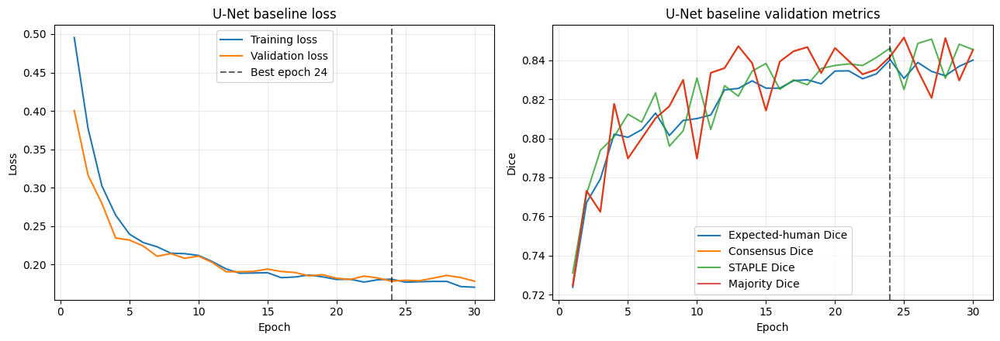

U-Net baseline locked successfully
Epochs completed: 30
Best epoch: 24
Stored human Dice:   0.840225
Restored human Dice: 0.840225
Difference: 0.00000000

Locked validation metrics:
validation_loss         : 0.178475
expected_human_dice     : 0.840225
consensus_dice          : 0.841817
staple_dice             : 0.846173
majority_dice           : 0.841817

Summary: /content/drive/MyDrive/MADSeg/outputs/unet_soft_consensus_baseline_v1/locked_validation_summary.json
Curves: /content/drive/MyDrive/MADSeg/outputs/unet_soft_consensus_baseline_v1/training_curves.png
Test set remains untouched.

Next: implement MAD-Seg.


In [ ]:
# ============================================================
# Lock and verify the completed U-Net baseline
# ============================================================

import json
import matplotlib.pyplot as plt
import pandas as pd
import torch

RUN_DIR = Path(
    "/content/drive/MyDrive/MADSeg/outputs/"
    "unet_soft_consensus_baseline_v1"
)

BEST_CHECKPOINT = RUN_DIR / "best_checkpoint.pt"
HISTORY_CSV = RUN_DIR / "history.csv"

assert BEST_CHECKPOINT.exists()
assert HISTORY_CSV.exists()

history_frame = pd.read_csv(HISTORY_CSV)

best_row_index = history_frame[
    "expected_human_dice"
].idxmax()

best_row = history_frame.loc[best_row_index]
best_epoch = int(best_row["epoch"])

checkpoint = torch.load(
    BEST_CHECKPOINT,
    map_location=DEVICE,
    weights_only=False,
)

baseline_model = UNet(
    in_channels=3,
    out_channels=1,
    base_channels=16,
).to(DEVICE)

baseline_model.load_state_dict(checkpoint["model_state"])
baseline_model.eval()

# Re-evaluate validation only
locked_validation_metrics = validate_model(
    baseline_model,
    validation_loader,
)

stored_score = float(best_row["expected_human_dice"])
restored_score = float(
    locked_validation_metrics["expected_human_dice"]
)
score_difference = abs(stored_score - restored_score)

assert score_difference < 1e-4, (
    "Restored validation score differs unexpectedly: "
    f"{score_difference}"
)

validation_summary = {
    "run_name": "unet_soft_consensus_baseline_v1",
    "best_epoch": best_epoch,
    "epochs_completed": int(len(history_frame)),
    "training_minutes": 42.12,
    "stored_expected_human_dice": stored_score,
    "restored_expected_human_dice": restored_score,
    "restoration_difference": score_difference,
    **{
        key: float(value)
        for key, value in locked_validation_metrics.items()
    },
    "test_evaluated": False,
}

summary_path = RUN_DIR / "locked_validation_summary.json"

with open(summary_path, "w", encoding="utf-8") as file:
    json.dump(validation_summary, file, indent=2)

# Learning curves
figure, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(
    history_frame["epoch"],
    history_frame["training_loss"],
    label="Training loss",
)
axes[0].plot(
    history_frame["epoch"],
    history_frame["validation_loss"],
    label="Validation loss",
)
axes[0].axvline(
    best_epoch,
    color="black",
    linestyle="--",
    alpha=0.6,
    label=f"Best epoch {best_epoch}",
)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("U-Net baseline loss")
axes[0].grid(alpha=0.25)
axes[0].legend()

axes[1].plot(
    history_frame["epoch"],
    history_frame["expected_human_dice"],
    label="Expected-human Dice",
)
axes[1].plot(
    history_frame["epoch"],
    history_frame["consensus_dice"],
    label="Consensus Dice",
)
axes[1].plot(
    history_frame["epoch"],
    history_frame["staple_dice"],
    label="STAPLE Dice",
    alpha=0.8,
)
axes[1].plot(
    history_frame["epoch"],
    history_frame["majority_dice"],
    label="Majority Dice",
    alpha=0.8,
)
axes[1].axvline(
    best_epoch,
    color="black",
    linestyle="--",
    alpha=0.6,
)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Dice")
axes[1].set_title("U-Net baseline validation metrics")
axes[1].grid(alpha=0.25)
axes[1].legend()

figure.tight_layout()

curve_path = RUN_DIR / "training_curves.png"
figure.savefig(curve_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close(figure)

print("U-Net baseline locked successfully")
print(f"Epochs completed: {len(history_frame)}")
print(f"Best epoch: {best_epoch}")
print(f"Stored human Dice:   {stored_score:.6f}")
print(f"Restored human Dice: {restored_score:.6f}")
print(f"Difference: {score_difference:.8f}")
print("\nLocked validation metrics:")
for key, value in locked_validation_metrics.items():
    print(f"{key:24s}: {value:.6f}")

print("\nSummary:", summary_path)
print("Curves:", curve_path)
print("Test set remains untouched.")
print("\nNext: implement MAD-Seg.")

**evaluation**

Full U-Net validation evaluation:   0%|          | 0/15 [00:00<?, ?it/s]

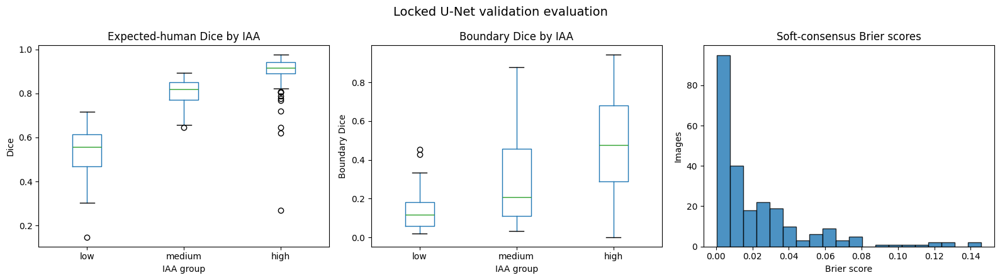


COMPREHENSIVE U-NET VALIDATION EVALUATION COMPLETE
Images evaluated: 240
Checkpoint epoch: 24

Segmentation:
Expected-human Dice: 0.840225
Expected-human IoU: 0.750428
Consensus Dice: 0.841817
STAPLE Dice: 0.846173
Majority Dice: 0.841817

Surface and boundary:
Expected-human HD95: 30.1305 px
Expected-human ASSD: 11.8820 px
Expected-human boundary Dice: 0.399895

Calibration:
Soft Brier: 0.022962
Soft NLL: 0.164756
Soft ECE-15: 0.043868

Efficiency:
Parameters: 1,942,577
GPU latency: 1.063 ms/image
GPU throughput: 940.66 images/second
Peak GPU memory: 1.12 GB

Saved files:
/content/drive/MyDrive/MADSeg/outputs/unet_soft_consensus_baseline_v1/validation_evaluation/per_image_metrics.csv
/content/drive/MyDrive/MADSeg/outputs/unet_soft_consensus_baseline_v1/validation_evaluation/metric_summary.csv
/content/drive/MyDrive/MADSeg/outputs/unet_soft_consensus_baseline_v1/validation_evaluation/bootstrap_95ci.csv
/content/drive/MyDrive/MADSeg/outputs/unet_soft_consensus_baseline_v1/validation_ev

In [ ]:
# ============================================================
# Comprehensive locked U-Net VALIDATION evaluation
# ============================================================

import json
import math
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from pathlib import Path
from scipy.ndimage import (
    binary_dilation,
    binary_erosion,
    distance_transform_edt,
)
from scipy.stats import spearmanr
from tqdm.auto import tqdm

warnings.filterwarnings("ignore", category=RuntimeWarning)

EVALUATION_DIR = RUN_DIR / "validation_evaluation"
EVALUATION_DIR.mkdir(parents=True, exist_ok=True)

PER_IMAGE_CSV = EVALUATION_DIR / "per_image_metrics.csv"
SUMMARY_CSV = EVALUATION_DIR / "metric_summary.csv"
BOOTSTRAP_CSV = EVALUATION_DIR / "bootstrap_95ci.csv"
IAA_CSV = EVALUATION_DIR / "metrics_by_iaa_group.csv"
ANNOTATION_COUNT_CSV = (
    EVALUATION_DIR / "metrics_by_annotation_count.csv"
)
CLINICAL_CSV = (
    EVALUATION_DIR / "clinical_subgroup_summary.csv"
)
EFFICIENCY_JSON = EVALUATION_DIR / "efficiency.json"
PROTOCOL_JSON = EVALUATION_DIR / "evaluation_protocol.json"
FIGURE_PATH = EVALUATION_DIR / "validation_overview.png"

PREDICTION_THRESHOLD = 0.5
BOUNDARY_TOLERANCE_PX = 2
ROI_DILATION_PX = 5
ECE_BINS = 15
BOOTSTRAP_REPETITIONS = 2000
BOOTSTRAP_SEED = 4201


# ------------------------------------------------------------
# Metric functions
# ------------------------------------------------------------

def overlap_metrics(prediction, target):
    prediction = np.asarray(prediction, dtype=bool)
    target = np.asarray(target, dtype=bool)

    tp = np.logical_and(prediction, target).sum(dtype=np.float64)
    tn = np.logical_and(~prediction, ~target).sum(dtype=np.float64)
    fp = np.logical_and(prediction, ~target).sum(dtype=np.float64)
    fn = np.logical_and(~prediction, target).sum(dtype=np.float64)

    dice_denominator = 2.0 * tp + fp + fn
    iou_denominator = tp + fp + fn
    precision_denominator = tp + fp
    recall_denominator = tp + fn
    specificity_denominator = tn + fp
    total = tp + tn + fp + fn

    dice = (
        1.0 if dice_denominator == 0
        else 2.0 * tp / dice_denominator
    )
    iou = (
        1.0 if iou_denominator == 0
        else tp / iou_denominator
    )
    precision = (
        1.0 if precision_denominator == 0 and target.sum() == 0
        else (
            0.0 if precision_denominator == 0
            else tp / precision_denominator
        )
    )
    recall = (
        1.0 if recall_denominator == 0 and prediction.sum() == 0
        else (
            0.0 if recall_denominator == 0
            else tp / recall_denominator
        )
    )
    specificity = (
        1.0
        if specificity_denominator == 0 and prediction.all()
        else (
            0.0 if specificity_denominator == 0
            else tn / specificity_denominator
        )
    )
    accuracy = (tp + tn) / total

    return {
        "dice": float(dice),
        "iou": float(iou),
        "precision": float(precision),
        "recall": float(recall),
        "specificity": float(specificity),
        "accuracy": float(accuracy),
    }


def one_pixel_surface(mask):
    mask = np.asarray(mask, dtype=bool)

    if not mask.any():
        return np.zeros_like(mask, dtype=bool)

    eroded = binary_erosion(
        mask,
        structure=np.ones((3, 3), dtype=bool),
        border_value=0,
    )

    return np.logical_and(mask, ~eroded)


def surface_distance_metrics(prediction, target):
    prediction = np.asarray(prediction, dtype=bool)
    target = np.asarray(target, dtype=bool)

    prediction_present = prediction.any()
    target_present = target.any()

    if not prediction_present and not target_present:
        return {"hd95_px": 0.0, "assd_px": 0.0}

    if not prediction_present or not target_present:
        diagonal = math.sqrt(
            prediction.shape[0] ** 2
            + prediction.shape[1] ** 2
        )
        return {
            "hd95_px": float(diagonal),
            "assd_px": float(diagonal),
        }

    prediction_surface = one_pixel_surface(prediction)
    target_surface = one_pixel_surface(target)

    distance_to_target = distance_transform_edt(
        ~target_surface
    )
    distance_to_prediction = distance_transform_edt(
        ~prediction_surface
    )

    prediction_to_target = distance_to_target[
        prediction_surface
    ]
    target_to_prediction = distance_to_prediction[
        target_surface
    ]

    symmetric_distances = np.concatenate([
        prediction_to_target,
        target_to_prediction,
    ])

    return {
        "hd95_px": float(
            np.percentile(symmetric_distances, 95)
        ),
        "assd_px": float(symmetric_distances.mean()),
    }


def boundary_dice(
    prediction,
    target,
    tolerance_px=BOUNDARY_TOLERANCE_PX,
):
    prediction_surface = one_pixel_surface(prediction)
    target_surface = one_pixel_surface(target)

    prediction_count = prediction_surface.sum()
    target_count = target_surface.sum()

    if prediction_count == 0 and target_count == 0:
        return 1.0

    if prediction_count == 0 or target_count == 0:
        return 0.0

    structure = np.ones(
        (2 * tolerance_px + 1, 2 * tolerance_px + 1),
        dtype=bool,
    )

    dilated_prediction = binary_dilation(
        prediction_surface,
        structure=structure,
    )
    dilated_target = binary_dilation(
        target_surface,
        structure=structure,
    )

    matched_prediction = np.logical_and(
        prediction_surface,
        dilated_target,
    ).sum()

    matched_target = np.logical_and(
        target_surface,
        dilated_prediction,
    ).sum()

    return float(
        (matched_prediction + matched_target)
        / (prediction_count + target_count)
    )


def complete_binary_metrics(prediction, target):
    result = overlap_metrics(prediction, target)
    result.update(surface_distance_metrics(prediction, target))
    result["boundary_dice"] = boundary_dice(
        prediction,
        target,
    )
    return result


def soft_brier_score(probability, soft_target):
    return float(
        np.mean((probability - soft_target) ** 2)
    )


def soft_nll(probability, soft_target, epsilon=1e-7):
    probability = np.clip(
        probability,
        epsilon,
        1.0 - epsilon,
    )

    return float(np.mean(
        -soft_target * np.log(probability)
        - (1.0 - soft_target) * np.log(1.0 - probability)
    ))


def soft_ece(probability, soft_target, number_of_bins=15):
    probability = probability.reshape(-1)
    soft_target = soft_target.reshape(-1)

    edges = np.linspace(0.0, 1.0, number_of_bins + 1)
    error = 0.0
    total = len(probability)

    for bin_index in range(number_of_bins):
        lower = edges[bin_index]
        upper = edges[bin_index + 1]

        if bin_index == number_of_bins - 1:
            selected = (
                (probability >= lower)
                & (probability <= upper)
            )
        else:
            selected = (
                (probability >= lower)
                & (probability < upper)
            )

        count = selected.sum()

        if count == 0:
            continue

        mean_probability = probability[selected].mean()
        mean_target = soft_target[selected].mean()

        error += (
            count / total
        ) * abs(mean_probability - mean_target)

    return float(error)


def normalized_entropy(probability, epsilon=1e-7):
    probability = np.clip(
        probability.astype(np.float32),
        epsilon,
        1.0 - epsilon,
    )

    return -(
        probability * np.log2(probability)
        + (1.0 - probability) * np.log2(
            1.0 - probability
        )
    )


def correlation_inside_roi(first, second, roi):
    selected_first = np.asarray(first)[roi].astype(np.float64)
    selected_second = np.asarray(second)[roi].astype(np.float64)

    finite = (
        np.isfinite(selected_first)
        & np.isfinite(selected_second)
    )

    selected_first = selected_first[finite]
    selected_second = selected_second[finite]

    if len(selected_first) < 10:
        return np.nan, np.nan

    if (
        np.std(selected_first) < 1e-10
        or np.std(selected_second) < 1e-10
    ):
        return np.nan, np.nan

    pearson = np.corrcoef(
        selected_first,
        selected_second,
    )[0, 1]

    spearman = spearmanr(
        selected_first,
        selected_second,
    ).correlation

    return float(pearson), float(spearman)


def prefix_metrics(metrics, prefix):
    return {
        f"{prefix}_{key}": value
        for key, value in metrics.items()
    }


# ------------------------------------------------------------
# Restore locked best model
# ------------------------------------------------------------

locked_checkpoint = torch.load(
    BEST_CHECKPOINT,
    map_location=DEVICE,
    weights_only=False,
)

evaluation_model = UNet(
    in_channels=3,
    out_channels=1,
    base_channels=16,
).to(DEVICE)

evaluation_model.load_state_dict(
    locked_checkpoint["model_state"]
)
evaluation_model.eval()

parameter_count = sum(
    parameter.numel()
    for parameter in evaluation_model.parameters()
)

assert parameter_count == 1_942_577


# ------------------------------------------------------------
# GPU warm-up
# ------------------------------------------------------------

with torch.inference_mode():
    warmup_image = torch.zeros(
        1, 3, 352, 352,
        device=DEVICE,
    )

    for _ in range(3):
        with torch.autocast(
            device_type="cuda",
            dtype=AMP_DTYPE,
        ):
            _ = evaluation_model(warmup_image)

torch.cuda.synchronize()
torch.cuda.reset_peak_memory_stats()


# ------------------------------------------------------------
# Per-image comprehensive evaluation
# ------------------------------------------------------------

records = []
total_gpu_inference_ms = 0.0
evaluated_images = 0

with torch.inference_mode():
    for evaluation_batch in tqdm(
        validation_loader,
        desc="Full U-Net validation evaluation",
    ):
        images_gpu = evaluation_batch["image"].to(
            DEVICE,
            non_blocking=True,
        )

        start_event = torch.cuda.Event(enable_timing=True)
        end_event = torch.cuda.Event(enable_timing=True)

        start_event.record()

        with torch.autocast(
            device_type="cuda",
            dtype=AMP_DTYPE,
        ):
            logits = evaluation_model(images_gpu)

        end_event.record()
        torch.cuda.synchronize()

        batch_inference_ms = start_event.elapsed_time(end_event)
        total_gpu_inference_ms += batch_inference_ms

        probabilities = torch.sigmoid(
            logits.float()
        ).cpu().numpy()[:, 0]

        batch_size = probabilities.shape[0]
        evaluated_images += batch_size

        for sample_index in range(batch_size):
            probability = probabilities[sample_index]
            prediction = probability >= PREDICTION_THRESHOLD

            mask_valid = (
                evaluation_batch["mask_valid"][sample_index]
                .cpu()
                .numpy()
                .astype(bool)
            )

            boundary_valid = (
                evaluation_batch["boundary_valid"][sample_index]
                .cpu()
                .numpy()
                .astype(bool)
            )

            human_masks = (
                evaluation_batch["human_masks"][sample_index]
                .cpu()
                .numpy()[mask_valid]
                > 0.5
            )

            valid_boundary_humans = (
                evaluation_batch["human_masks"][sample_index]
                .cpu()
                .numpy()[boundary_valid]
                > 0.5
            )

            soft_target = (
                evaluation_batch["soft_consensus"][sample_index, 0]
                .cpu()
                .numpy()
            )

            hard_target = (
                evaluation_batch["hard_consensus"][sample_index, 0]
                .cpu()
                .numpy()
                > 0.5
            )

            staple_target = (
                evaluation_batch["staple_mask"][sample_index, 0]
                .cpu()
                .numpy()
                > 0.5
            )

            majority_target = (
                evaluation_batch["majority_mask"][sample_index, 0]
                .cpu()
                .numpy()
                > 0.5
            )

            human_disagreement = (
                evaluation_batch[
                    "human_disagreement"
                ][sample_index, 0]
                .cpu()
                .numpy()
            )

            boundary_disagreement = (
                evaluation_batch[
                    "boundary_disagreement"
                ][sample_index, 0]
                .cpu()
                .numpy()
            )

            consensus_boundary = (
                evaluation_batch[
                    "consensus_boundary"
                ][sample_index, 0]
                .cpu()
                .numpy()
                > 0.5
            )

            predictive_entropy = normalized_entropy(
                probability
            )

            record = {
                "iaa_id": int(
                    evaluation_batch["iaa_id"][sample_index]
                ),
                "isic_id": evaluation_batch[
                    "isic_id"
                ][sample_index],
                "split": evaluation_batch[
                    "split"
                ][sample_index],
                "iaa_group": evaluation_batch[
                    "iaa_group"
                ][sample_index],
                "num_human_masks": int(mask_valid.sum()),
            }

            # Expected overlap metrics against individual humans
            individual_overlap = [
                overlap_metrics(prediction, human_target)
                for human_target in human_masks
            ]

            for metric_name in [
                "dice",
                "iou",
                "precision",
                "recall",
                "specificity",
                "accuracy",
            ]:
                record[f"expected_human_{metric_name}"] = float(
                    np.mean([
                        result[metric_name]
                        for result in individual_overlap
                    ])
                )

            # Human surface/boundary comparisons exclude invalid
            # full/empty individual boundaries.
            if len(valid_boundary_humans) > 0:
                human_surface_results = [
                    surface_distance_metrics(
                        prediction,
                        human_target,
                    )
                    for human_target in valid_boundary_humans
                ]

                record["expected_human_hd95_px"] = float(
                    np.mean([
                        result["hd95_px"]
                        for result in human_surface_results
                    ])
                )

                record["expected_human_assd_px"] = float(
                    np.mean([
                        result["assd_px"]
                        for result in human_surface_results
                    ])
                )

                record["expected_human_boundary_dice"] = float(
                    np.mean([
                        boundary_dice(
                            prediction,
                            human_target,
                        )
                        for human_target in valid_boundary_humans
                    ])
                )
            else:
                record["expected_human_hd95_px"] = np.nan
                record["expected_human_assd_px"] = np.nan
                record["expected_human_boundary_dice"] = np.nan

            # Consensus, STAPLE and majority-vote references
            record.update(prefix_metrics(
                complete_binary_metrics(
                    prediction,
                    hard_target,
                ),
                "consensus",
            ))

            record.update(prefix_metrics(
                complete_binary_metrics(
                    prediction,
                    staple_target,
                ),
                "staple",
            ))

            record.update(prefix_metrics(
                complete_binary_metrics(
                    prediction,
                    majority_target,
                ),
                "majority",
            ))

            # Calibration against soft human consensus
            record["soft_brier"] = soft_brier_score(
                probability,
                soft_target,
            )
            record["soft_nll"] = soft_nll(
                probability,
                soft_target,
            )
            record["soft_ece_15"] = soft_ece(
                probability,
                soft_target,
                ECE_BINS,
            )

            record["mean_predictive_entropy"] = float(
                predictive_entropy.mean()
            )

            # Predeclared lesion and boundary neighborhoods
            human_union = np.any(human_masks, axis=0)

            lesion_roi = binary_dilation(
                human_union,
                iterations=ROI_DILATION_PX,
            )

            boundary_roi = binary_dilation(
                consensus_boundary,
                iterations=ROI_DILATION_PX,
            )

            lesion_pearson, lesion_spearman = (
                correlation_inside_roi(
                    predictive_entropy,
                    human_disagreement,
                    lesion_roi,
                )
            )

            boundary_pearson, boundary_spearman = (
                correlation_inside_roi(
                    predictive_entropy,
                    boundary_disagreement,
                    boundary_roi,
                )
            )

            record[
                "entropy_human_disagreement_pearson"
            ] = lesion_pearson
            record[
                "entropy_human_disagreement_spearman"
            ] = lesion_spearman
            record[
                "entropy_boundary_disagreement_pearson"
            ] = boundary_pearson
            record[
                "entropy_boundary_disagreement_spearman"
            ] = boundary_spearman

            records.append(record)


assert evaluated_images == 240
assert all(record["split"] == "validation" for record in records)

per_image = pd.DataFrame(records)


# ------------------------------------------------------------
# Add available clinical metadata
# ------------------------------------------------------------

clinical_columns = [
    "isic_id",
    "age_approx",
    "sex",
    "anatom_site_general",
    "benign_malignant",
    "diagnosis_1",
    "diagnosis_2",
    "diagnosis_3",
]

available_clinical_columns = [
    column
    for column in clinical_columns
    if column in canonical_manifest.columns
]

clinical_metadata = (
    canonical_manifest[available_clinical_columns]
    .drop_duplicates(subset=["isic_id"])
)

per_image = per_image.merge(
    clinical_metadata,
    on="isic_id",
    how="left",
    validate="one_to_one",
)

per_image.to_csv(PER_IMAGE_CSV, index=False)


# ------------------------------------------------------------
# Overall summary
# ------------------------------------------------------------

identifier_columns = {
    "iaa_id",
    "isic_id",
    "split",
    "iaa_group",
    "num_human_masks",
    "age_approx",
    "sex",
    "anatom_site_general",
    "benign_malignant",
    "diagnosis_1",
    "diagnosis_2",
    "diagnosis_3",
}

metric_columns = [
    column
    for column in per_image.columns
    if column not in identifier_columns
    and pd.api.types.is_numeric_dtype(per_image[column])
]

summary_rows = []

for metric_name in metric_columns:
    values = per_image[metric_name].dropna()

    summary_rows.append({
        "metric": metric_name,
        "n": len(values),
        "mean": values.mean(),
        "std": values.std(ddof=1),
        "median": values.median(),
        "minimum": values.min(),
        "maximum": values.max(),
    })

metric_summary = pd.DataFrame(summary_rows)
metric_summary.to_csv(SUMMARY_CSV, index=False)


# ------------------------------------------------------------
# Bootstrap 95% confidence intervals
# ------------------------------------------------------------

bootstrap_metrics = [
    "expected_human_dice",
    "expected_human_iou",
    "expected_human_precision",
    "expected_human_recall",
    "expected_human_specificity",
    "expected_human_hd95_px",
    "expected_human_assd_px",
    "expected_human_boundary_dice",
    "consensus_dice",
    "consensus_iou",
    "consensus_hd95_px",
    "consensus_assd_px",
    "consensus_boundary_dice",
    "staple_dice",
    "majority_dice",
    "soft_brier",
    "soft_nll",
    "soft_ece_15",
    "entropy_human_disagreement_spearman",
    "entropy_boundary_disagreement_spearman",
]

bootstrap_rng = np.random.default_rng(BOOTSTRAP_SEED)
bootstrap_rows = []

for metric_name in bootstrap_metrics:
    values = (
        per_image[metric_name]
        .dropna()
        .to_numpy(dtype=np.float64)
    )

    sample_indices = bootstrap_rng.integers(
        0,
        len(values),
        size=(BOOTSTRAP_REPETITIONS, len(values)),
    )

    bootstrap_means = values[sample_indices].mean(axis=1)

    bootstrap_rows.append({
        "metric": metric_name,
        "n": len(values),
        "mean": values.mean(),
        "ci95_lower": np.percentile(
            bootstrap_means, 2.5
        ),
        "ci95_upper": np.percentile(
            bootstrap_means, 97.5
        ),
        "bootstrap_repetitions": BOOTSTRAP_REPETITIONS,
        "bootstrap_seed": BOOTSTRAP_SEED,
    })

bootstrap_summary = pd.DataFrame(bootstrap_rows)
bootstrap_summary.to_csv(BOOTSTRAP_CSV, index=False)


# ------------------------------------------------------------
# IAA and annotation-count stratification
# ------------------------------------------------------------

reported_group_metrics = [
    "expected_human_dice",
    "expected_human_iou",
    "expected_human_hd95_px",
    "expected_human_assd_px",
    "expected_human_boundary_dice",
    "consensus_dice",
    "soft_brier",
    "soft_ece_15",
    "entropy_human_disagreement_spearman",
    "entropy_boundary_disagreement_spearman",
]

iaa_summary = (
    per_image
    .groupby("iaa_group", dropna=False)
    .agg(
        images=("isic_id", "count"),
        **{
            metric_name: (metric_name, "mean")
            for metric_name in reported_group_metrics
        },
    )
    .reset_index()
)

iaa_summary["iaa_group"] = pd.Categorical(
    iaa_summary["iaa_group"],
    categories=["low", "medium", "high"],
    ordered=True,
)

iaa_summary = iaa_summary.sort_values("iaa_group")
iaa_summary.to_csv(IAA_CSV, index=False)

annotation_count_summary = (
    per_image
    .groupby("num_human_masks", dropna=False)
    .agg(
        images=("isic_id", "count"),
        **{
            metric_name: (metric_name, "mean")
            for metric_name in reported_group_metrics
        },
    )
    .reset_index()
)

annotation_count_summary.to_csv(
    ANNOTATION_COUNT_CSV,
    index=False,
)


# ------------------------------------------------------------
# Clinical subgroup summaries
# ------------------------------------------------------------

clinical_rows = []

for group_column in [
    "sex",
    "anatom_site_general",
    "benign_malignant",
    "diagnosis_1",
]:
    if group_column not in per_image.columns:
        continue

    for group_value, group_frame in per_image.groupby(
        group_column,
        dropna=True,
    ):
        # Avoid presenting extremely small subgroups
        if len(group_frame) < 5:
            continue

        clinical_rows.append({
            "group_variable": group_column,
            "group_value": group_value,
            "images": len(group_frame),
            "expected_human_dice": group_frame[
                "expected_human_dice"
            ].mean(),
            "expected_human_iou": group_frame[
                "expected_human_iou"
            ].mean(),
            "expected_human_hd95_px": group_frame[
                "expected_human_hd95_px"
            ].mean(),
            "expected_human_boundary_dice": group_frame[
                "expected_human_boundary_dice"
            ].mean(),
            "soft_brier": group_frame[
                "soft_brier"
            ].mean(),
        })

clinical_summary = pd.DataFrame(clinical_rows)
clinical_summary.to_csv(CLINICAL_CSV, index=False)


# ------------------------------------------------------------
# Efficiency and protocol records
# ------------------------------------------------------------

peak_gpu_memory_gb = (
    torch.cuda.max_memory_allocated() / 1024**3
)

mean_gpu_latency_ms = (
    total_gpu_inference_ms / evaluated_images
)

gpu_throughput = (
    evaluated_images
    / (total_gpu_inference_ms / 1000.0)
)

efficiency = {
    "model": "UNet",
    "parameters": int(parameter_count),
    "resolution": [352, 352],
    "batch_size": int(validation_loader.batch_size),
    "images": int(evaluated_images),
    "gpu": torch.cuda.get_device_name(0),
    "amp_dtype": str(AMP_DTYPE),
    "gpu_only_latency_ms_per_image": mean_gpu_latency_ms,
    "gpu_only_images_per_second": gpu_throughput,
    "peak_allocated_gpu_memory_gb": peak_gpu_memory_gb,
    "gflops": None,
    "gflops_note": (
        "Pending common architecture profiler; not estimated "
        "manually."
    ),
}

with open(EFFICIENCY_JSON, "w", encoding="utf-8") as file:
    json.dump(efficiency, file, indent=2)

protocol = {
    "model": "unet_soft_consensus_baseline_v1",
    "checkpoint_epoch": int(
        locked_checkpoint["epoch"]
    ),
    "evaluation_split": "validation",
    "test_set_evaluated": False,
    "prediction_threshold": PREDICTION_THRESHOLD,
    "boundary_tolerance_px": BOUNDARY_TOLERANCE_PX,
    "surface_distance_units": "resized 352x352 pixels",
    "empty_surface_policy": (
        "both empty = 0 distance; exactly one empty = "
        "image diagonal"
    ),
    "calibration_target": "mean soft human consensus",
    "ece_bins": ECE_BINS,
    "uncertainty_proxy": (
        "normalized entropy of U-Net sigmoid probability"
    ),
    "alignment_lesion_roi": (
        f"human-mask union dilated by {ROI_DILATION_PX} pixels"
    ),
    "alignment_boundary_roi": (
        f"consensus-boundary region dilated by "
        f"{ROI_DILATION_PX} pixels"
    ),
    "bootstrap_repetitions": BOOTSTRAP_REPETITIONS,
    "bootstrap_seed": BOOTSTRAP_SEED,
    "not_applicable_to_unet": [
        "learned_disagreement_head_accuracy",
        "learned_boundary_probability_accuracy",
        "annotator_conditioned_branch_metrics",
        "metadata_ablation",
        "cross_branch_consistency",
    ],
}

with open(PROTOCOL_JSON, "w", encoding="utf-8") as file:
    json.dump(protocol, file, indent=2)


# ------------------------------------------------------------
# Overview figure
# ------------------------------------------------------------

figure, axes = plt.subplots(1, 3, figsize=(16, 4.5))

iaa_plot = per_image.copy()
iaa_plot["iaa_group"] = pd.Categorical(
    iaa_plot["iaa_group"],
    categories=["low", "medium", "high"],
    ordered=True,
)

iaa_plot.boxplot(
    column="expected_human_dice",
    by="iaa_group",
    ax=axes[0],
    grid=False,
)
axes[0].set_title("Expected-human Dice by IAA")
axes[0].set_xlabel("IAA group")
axes[0].set_ylabel("Dice")

iaa_plot.boxplot(
    column="expected_human_boundary_dice",
    by="iaa_group",
    ax=axes[1],
    grid=False,
)
axes[1].set_title("Boundary Dice by IAA")
axes[1].set_xlabel("IAA group")
axes[1].set_ylabel("Boundary Dice")

axes[2].hist(
    per_image["soft_brier"],
    bins=20,
    edgecolor="black",
    alpha=0.8,
)
axes[2].set_title("Soft-consensus Brier scores")
axes[2].set_xlabel("Brier score")
axes[2].set_ylabel("Images")

figure.suptitle(
    "Locked U-Net validation evaluation",
    fontsize=14,
)
figure.tight_layout()
figure.savefig(
    FIGURE_PATH,
    dpi=180,
    bbox_inches="tight",
)
plt.show()
plt.close(figure)


# ------------------------------------------------------------
# Essential output
# ------------------------------------------------------------

def summary_mean(metric_name):
    return float(
        metric_summary.loc[
            metric_summary["metric"] == metric_name,
            "mean",
        ].iloc[0]
    )


print("\nCOMPREHENSIVE U-NET VALIDATION EVALUATION COMPLETE")
print(f"Images evaluated: {evaluated_images}")
print(f"Checkpoint epoch: {locked_checkpoint['epoch']}")

print("\nSegmentation:")
print(
    "Expected-human Dice:",
    f"{summary_mean('expected_human_dice'):.6f}",
)
print(
    "Expected-human IoU:",
    f"{summary_mean('expected_human_iou'):.6f}",
)
print(
    "Consensus Dice:",
    f"{summary_mean('consensus_dice'):.6f}",
)
print(
    "STAPLE Dice:",
    f"{summary_mean('staple_dice'):.6f}",
)
print(
    "Majority Dice:",
    f"{summary_mean('majority_dice'):.6f}",
)

print("\nSurface and boundary:")
print(
    "Expected-human HD95:",
    f"{summary_mean('expected_human_hd95_px'):.4f} px",
)
print(
    "Expected-human ASSD:",
    f"{summary_mean('expected_human_assd_px'):.4f} px",
)
print(
    "Expected-human boundary Dice:",
    f"{summary_mean('expected_human_boundary_dice'):.6f}",
)

print("\nCalibration:")
print(
    "Soft Brier:",
    f"{summary_mean('soft_brier'):.6f}",
)
print(
    "Soft NLL:",
    f"{summary_mean('soft_nll'):.6f}",
)
print(
    "Soft ECE-15:",
    f"{summary_mean('soft_ece_15'):.6f}",
)

print("\nEfficiency:")
print(f"Parameters: {parameter_count:,}")
print(
    "GPU latency:",
    f"{mean_gpu_latency_ms:.3f} ms/image",
)
print(
    "GPU throughput:",
    f"{gpu_throughput:.2f} images/second",
)
print(
    "Peak GPU memory:",
    f"{peak_gpu_memory_gb:.2f} GB",
)

print("\nSaved files:")
for saved_path in [
    PER_IMAGE_CSV,
    SUMMARY_CSV,
    BOOTSTRAP_CSV,
    IAA_CSV,
    ANNOTATION_COUNT_CSV,
    CLINICAL_CSV,
    EFFICIENCY_JSON,
    PROTOCOL_JSON,
    FIGURE_PATH,
]:
    print(saved_path)

print("\nTest set remains untouched.")

In [ ]:
# Display the remaining saved U-Net evaluation tables

evaluation_dir = Path(
    "/content/drive/MyDrive/MADSeg/outputs/"
    "unet_soft_consensus_baseline_v1/validation_evaluation"
)

iaa_results = pd.read_csv(
    evaluation_dir / "metrics_by_iaa_group.csv"
)

annotation_results = pd.read_csv(
    evaluation_dir / "metrics_by_annotation_count.csv"
)

bootstrap_results = pd.read_csv(
    evaluation_dir / "bootstrap_95ci.csv"
)

print("METRICS BY IAA GROUP")
display(iaa_results.round(6))

print("\nMETRICS BY ANNOTATION COUNT")
display(annotation_results.round(6))

print("\nPRIMARY BOOTSTRAP 95% CONFIDENCE INTERVALS")
display(
    bootstrap_results[
        bootstrap_results["metric"].isin([
            "expected_human_dice",
            "expected_human_iou",
            "expected_human_hd95_px",
            "expected_human_assd_px",
            "expected_human_boundary_dice",
            "consensus_dice",
            "soft_brier",
            "soft_ece_15",
        ])
    ].round(6)
)

METRICS BY IAA GROUP


,iaa_group,images,expected_human_dice,expected_human_iou,expected_human_hd95_px,expected_human_assd_px,expected_human_boundary_dice,consensus_dice,soft_brier,soft_ece_15,entropy_human_disagreement_spearman,entropy_boundary_disagreement_spearman
0,low,24,0.521701,0.389184,83.333173,39.054462,0.149116,0.560613,0.057455,0.119508,0.171924,0.051690
1,medium,58,0.801561,0.681473,35.195045,13.690112,0.287661,0.801994,0.023582,0.038761,0.358203,0.125722
2,high,158,0.902802,0.830613,20.189887,7.090780,0.479188,0.899150,0.017494,0.034252,0.104859,0.228632



METRICS BY ANNOTATION COUNT


,num_human_masks,images,expected_human_dice,expected_human_iou,expected_human_hd95_px,expected_human_assd_px,expected_human_boundary_dice,consensus_dice,soft_brier,soft_ece_15,entropy_human_disagreement_spearman,entropy_boundary_disagreement_spearman
0,2,214,0.847877,0.759681,27.424020,10.562682,0.424624,0.843127,0.019505,0.037102,0.157694,0.201044
1,3,19,0.739025,0.624475,58.722333,25.771259,0.169181,0.799611,0.058552,0.113342,0.281883,0.038529
2,4,6,0.913801,0.845988,25.119785,9.334303,0.297582,0.927281,0.024516,0.049334,0.405369,0.130582
3,5,1,0.683988,0.589882,96.127547,45.603108,0.105503,0.850646,0.077063,0.138847,-0.064744,0.117285



PRIMARY BOOTSTRAP 95% CONFIDENCE INTERVALS


,metric,n,mean,ci95_lower,ci95_upper,bootstrap_repetitions,bootstrap_seed
0,expected_human_dice,240,0.840225,0.822935,0.857180,2000,4201
1,expected_human_iou,240,0.750428,0.728209,0.771233,2000,4201
5,expected_human_hd95_px,240,30.130462,25.967023,34.781480,2000,4201
6,expected_human_assd_px,240,11.881987,10.276508,13.633238,2000,4201
7,expected_human_boundary_dice,240,0.399895,0.367050,0.431312,2000,4201
8,consensus_dice,240,0.841817,0.822461,0.859455,2000,4201
15,soft_brier,240,0.022962,0.019654,0.026873,2000,4201
17,soft_ece_15,240,0.043868,0.037155,0.051233,2000,4201


# MAD-Seg

In [ ]:
%%writefile /content/drive/MyDrive/MADSeg/madseg_model.py

import torch
import torch.nn as nn
import torch.nn.functional as F


class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1,
                bias=False,
            ),
            nn.GroupNorm(8, out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1,
                bias=False,
            ),
            nn.GroupNorm(8, out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class SharedEncoder(nn.Module):
    def __init__(self, in_channels=3, base_channels=16):
        super().__init__()

        c1 = base_channels
        c2 = c1 * 2
        c3 = c1 * 4
        c4 = c1 * 8
        c5 = c1 * 16

        self.encoder1 = DoubleConv(in_channels, c1)
        self.encoder2 = DoubleConv(c1, c2)
        self.encoder3 = DoubleConv(c2, c3)
        self.encoder4 = DoubleConv(c3, c4)
        self.bottleneck = DoubleConv(c4, c5)
        self.pool = nn.MaxPool2d(2)

    def forward(self, x):
        e1 = self.encoder1(x)
        e2 = self.encoder2(self.pool(e1))
        e3 = self.encoder3(self.pool(e2))
        e4 = self.encoder4(self.pool(e3))
        bottleneck = self.bottleneck(self.pool(e4))

        return e1, e2, e3, e4, bottleneck


class SegmentationDecoder(nn.Module):
    def __init__(self, base_channels=16):
        super().__init__()

        c1 = base_channels
        c2 = c1 * 2
        c3 = c1 * 4
        c4 = c1 * 8
        c5 = c1 * 16

        self.up4 = nn.ConvTranspose2d(c5, c4, 2, 2)
        self.decoder4 = DoubleConv(c4 + c4, c4)

        self.up3 = nn.ConvTranspose2d(c4, c3, 2, 2)
        self.decoder3 = DoubleConv(c3 + c3, c3)

        self.up2 = nn.ConvTranspose2d(c3, c2, 2, 2)
        self.decoder2 = DoubleConv(c2 + c2, c2)

        self.up1 = nn.ConvTranspose2d(c2, c1, 2, 2)
        self.decoder1 = DoubleConv(c1 + c1, c1)

    def forward(self, encoder_features):
        e1, e2, e3, e4, bottleneck = encoder_features

        d4 = self.up4(bottleneck)
        d4 = self.decoder4(torch.cat([d4, e4], dim=1))

        d3 = self.up3(d4)
        d3 = self.decoder3(torch.cat([d3, e3], dim=1))

        d2 = self.up2(d3)
        d2 = self.decoder2(torch.cat([d2, e2], dim=1))

        d1 = self.up1(d2)
        d1 = self.decoder1(torch.cat([d1, e1], dim=1))

        return d1


class MetadataConditioner(nn.Module):
    def __init__(
        self,
        feature_channels,
        number_of_annotators,
        number_of_tools,
        number_of_skills,
        embedding_dimension=8,
    ):
        super().__init__()

        # Index zero is reserved for padded metadata.
        self.annotator_embedding = nn.Embedding(
            number_of_annotators + 1,
            embedding_dimension,
            padding_idx=0,
        )
        self.tool_embedding = nn.Embedding(
            number_of_tools + 1,
            embedding_dimension,
            padding_idx=0,
        )
        self.skill_embedding = nn.Embedding(
            number_of_skills + 1,
            embedding_dimension,
            padding_idx=0,
        )

        self.film_network = nn.Sequential(
            nn.Linear(embedding_dimension * 3, 32),
            nn.ReLU(inplace=True),
            nn.Linear(32, feature_channels * 2),
        )

        nn.init.normal_(
            self.film_network[-1].weight,
            mean=0.0,
            std=0.01,
        )
        nn.init.zeros_(self.film_network[-1].bias)

    @staticmethod
    def prepare_ids(ids, maximum_id):
        # Dataset padding is -1; embedding padding is zero.
        return (ids + 1).clamp(min=0, max=maximum_id)

    def forward(
        self,
        features,
        annotator_ids,
        tool_ids,
        skill_ids,
    ):
        annotator_ids = self.prepare_ids(
            annotator_ids,
            self.annotator_embedding.num_embeddings - 1,
        )
        tool_ids = self.prepare_ids(
            tool_ids,
            self.tool_embedding.num_embeddings - 1,
        )
        skill_ids = self.prepare_ids(
            skill_ids,
            self.skill_embedding.num_embeddings - 1,
        )

        metadata = torch.cat([
            self.annotator_embedding(annotator_ids),
            self.tool_embedding(tool_ids),
            self.skill_embedding(skill_ids),
        ], dim=-1)

        film_parameters = self.film_network(metadata)
        gamma, beta = film_parameters.chunk(2, dim=-1)

        # Keep initial modulation small and stable.
        gamma = 0.1 * torch.tanh(gamma)
        beta = 0.1 * torch.tanh(beta)

        conditioned = (
            features[:, None]
            * (1.0 + gamma[..., None, None])
            + beta[..., None, None]
        )

        return conditioned


class MADSeg(nn.Module):
    """
    Multi-Annotator Disagreement-Aware Segmentation.

    Inference requires only an RGB image. Annotator/tool/skill
    metadata are used only by the training-time auxiliary branch.
    """

    def __init__(
        self,
        in_channels=3,
        base_channels=16,
        number_of_annotators=15,
        number_of_tools=3,
        number_of_skills=2,
        embedding_dimension=8,
    ):
        super().__init__()

        c1 = base_channels

        self.encoder = SharedEncoder(
            in_channels=in_channels,
            base_channels=base_channels,
        )

        self.consensus_decoder = SegmentationDecoder(
            base_channels=base_channels,
        )

        self.ambiguity_decoder = SegmentationDecoder(
            base_channels=base_channels,
        )

        self.raw_consensus_head = nn.Conv2d(c1, 1, 1)
        self.boundary_head = nn.Conv2d(c1, 1, 1)
        self.disagreement_head = nn.Conv2d(c1, 1, 1)

        # Fuse consensus features, ambiguity features, predicted
        # boundary probability, and predicted disagreement.
        self.disagreement_fusion = DoubleConv(
            c1 + c1 + 2,
            c1,
        )

        self.final_residual_head = nn.Conv2d(c1, 1, 1)

        self.metadata_conditioner = MetadataConditioner(
            feature_channels=c1,
            number_of_annotators=number_of_annotators,
            number_of_tools=number_of_tools,
            number_of_skills=number_of_skills,
            embedding_dimension=embedding_dimension,
        )

        self.annotator_head = nn.Conv2d(c1, 1, 1)

    def forward(
        self,
        image,
        annotator_ids=None,
        tool_ids=None,
        skill_ids=None,
        return_annotator_logits=None,
    ):
        encoder_features = self.encoder(image)

        consensus_features = self.consensus_decoder(
            encoder_features
        )
        ambiguity_features = self.ambiguity_decoder(
            encoder_features
        )

        raw_consensus_logits = self.raw_consensus_head(
            consensus_features
        )
        boundary_logits = self.boundary_head(
            ambiguity_features
        )
        disagreement_logits = self.disagreement_head(
            ambiguity_features
        )

        fusion_input = torch.cat([
            consensus_features,
            ambiguity_features,
            torch.sigmoid(boundary_logits),
            torch.sigmoid(disagreement_logits),
        ], dim=1)

        fused_features = self.disagreement_fusion(
            fusion_input
        )

        final_mask_logits = (
            raw_consensus_logits
            + self.final_residual_head(fused_features)
        )

        if return_annotator_logits is None:
            return_annotator_logits = all(
                value is not None
                for value in [
                    annotator_ids,
                    tool_ids,
                    skill_ids,
                ]
            )

        annotator_logits = None

        if return_annotator_logits:
            if any(
                value is None
                for value in [
                    annotator_ids,
                    tool_ids,
                    skill_ids,
                ]
            ):
                raise ValueError(
                    "All metadata IDs are required for the "
                    "annotator-conditioned training branch."
                )

            conditioned_features = self.metadata_conditioner(
                consensus_features,
                annotator_ids,
                tool_ids,
                skill_ids,
            )

            batch_size, annotations, channels, height, width = (
                conditioned_features.shape
            )

            conditioned_features = (
                conditioned_features.reshape(
                    batch_size * annotations,
                    channels,
                    height,
                    width,
                )
            )

            annotator_logits = self.annotator_head(
                conditioned_features
            ).reshape(
                batch_size,
                annotations,
                height,
                width,
            )

        return {
            "final_mask_logits": final_mask_logits,
            "raw_consensus_logits": raw_consensus_logits,
            "boundary_logits": boundary_logits,
            "disagreement_logits": disagreement_logits,
            "uncertainty_map": torch.sigmoid(
                disagreement_logits
            ),
            "annotator_logits": annotator_logits,
        }


def soft_dice_loss(logits, target, epsilon=1e-6):
    probability = torch.sigmoid(logits)

    dimensions = tuple(range(1, probability.ndim))
    intersection = (probability * target).sum(dim=dimensions)

    denominator = (
        probability.sum(dim=dimensions)
        + target.sum(dim=dimensions)
    )

    dice = (
        2.0 * intersection + epsilon
    ) / (
        denominator + epsilon
    )

    return 1.0 - dice.mean()


def segmentation_loss(logits, target):
    bce = F.binary_cross_entropy_with_logits(
        logits,
        target,
    )
    dice = soft_dice_loss(logits, target)

    return 0.5 * bce + 0.5 * dice


class MADSegLoss(nn.Module):
    def __init__(
        self,
        lambda_segmentation=1.0,
        lambda_soft_consensus=0.5,
        lambda_boundary=0.3,
        lambda_disagreement=0.3,
        lambda_annotator=0.5,
        lambda_consistency=0.1,
    ):
        super().__init__()

        self.weights = {
            "segmentation": lambda_segmentation,
            "soft_consensus": lambda_soft_consensus,
            "boundary": lambda_boundary,
            "disagreement": lambda_disagreement,
            "annotator": lambda_annotator,
            "consistency": lambda_consistency,
        }

    def forward(self, outputs, batch):
        segmentation = segmentation_loss(
            outputs["final_mask_logits"],
            batch["soft_consensus"],
        )

        soft_consensus = segmentation_loss(
            outputs["raw_consensus_logits"],
            batch["soft_consensus"],
        )

        boundary = segmentation_loss(
            outputs["boundary_logits"],
            batch["boundary_probability"],
        )

        disagreement_probability = torch.sigmoid(
            outputs["disagreement_logits"]
        )

        disagreement = F.smooth_l1_loss(
            disagreement_probability,
            batch["human_disagreement"],
        )

        annotator_logits = outputs["annotator_logits"]
        valid_annotations = batch["mask_valid"]

        if (
            annotator_logits is not None
            and valid_annotations.any()
        ):
            annotator = segmentation_loss(
                annotator_logits[valid_annotations],
                batch["human_masks"][valid_annotations],
            )
        else:
            annotator = outputs[
                "final_mask_logits"
            ].sum() * 0.0

        consistency = F.l1_loss(
            torch.sigmoid(outputs["final_mask_logits"]),
            torch.sigmoid(outputs["raw_consensus_logits"]),
        )

        total = (
            self.weights["segmentation"] * segmentation
            + self.weights["soft_consensus"] * soft_consensus
            + self.weights["boundary"] * boundary
            + self.weights["disagreement"] * disagreement
            + self.weights["annotator"] * annotator
            + self.weights["consistency"] * consistency
        )

        return {
            "total": total,
            "segmentation": segmentation,
            "soft_consensus": soft_consensus,
            "boundary": boundary,
            "disagreement": disagreement,
            "annotator": annotator,
            "consistency": consistency,
        }

Writing /content/drive/MyDrive/MADSeg/madseg_model.py


In [ ]:
# ============================================================
# MAD-Seg architecture, loss and metadata-free inference test
# ============================================================

import importlib
import sys
import torch

MODULE_ROOT = "/content/drive/MyDrive/MADSeg"

if MODULE_ROOT not in sys.path:
    sys.path.insert(0, MODULE_ROOT)

import madseg_model
importlib.reload(madseg_model)

from madseg_model import MADSeg, MADSegLoss


torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

madseg = MADSeg(
    in_channels=3,
    base_channels=16,
    number_of_annotators=len(ANNOTATOR_TO_ID),
    number_of_tools=len(TOOL_TO_ID),
    number_of_skills=len(SKILL_TO_ID),
    embedding_dimension=8,
).to(DEVICE)

madseg_loss = MADSegLoss().to(DEVICE)

test_batch = next(iter(train_loader))
SMOKE_BATCH_SIZE = 2

gpu_batch = {}

tensor_keys = [
    "image",
    "human_masks",
    "mask_valid",
    "boundary_probability",
    "human_disagreement",
    "soft_consensus",
    "annotator_ids",
    "tool_ids",
    "skill_ids",
]

for key in tensor_keys:
    gpu_batch[key] = test_batch[key][
        :SMOKE_BATCH_SIZE
    ].to(
        DEVICE,
        non_blocking=True,
    )

madseg.train()
madseg.zero_grad(set_to_none=True)

with torch.autocast(
    device_type="cuda",
    dtype=AMP_DTYPE,
):
    outputs = madseg(
        gpu_batch["image"],
        annotator_ids=gpu_batch["annotator_ids"],
        tool_ids=gpu_batch["tool_ids"],
        skill_ids=gpu_batch["skill_ids"],
        return_annotator_logits=True,
    )

    losses = madseg_loss(outputs, gpu_batch)

assert outputs["final_mask_logits"].shape == (
    SMOKE_BATCH_SIZE, 1, 352, 352
)
assert outputs["boundary_logits"].shape == (
    SMOKE_BATCH_SIZE, 1, 352, 352
)
assert outputs["disagreement_logits"].shape == (
    SMOKE_BATCH_SIZE, 1, 352, 352
)
assert outputs["annotator_logits"].shape == (
    SMOKE_BATCH_SIZE, 5, 352, 352
)

for name, value in losses.items():
    assert torch.isfinite(value), (
        f"Non-finite loss: {name}"
    )

losses["total"].backward()

parameters_with_gradients = 0
finite_gradient_parameters = 0

for parameter in madseg.parameters():
    if parameter.grad is not None:
        parameters_with_gradients += 1

        if torch.isfinite(parameter.grad).all():
            finite_gradient_parameters += 1

assert parameters_with_gradients > 0
assert (
    parameters_with_gradients
    == finite_gradient_parameters
)

# Confirm metadata-free inference
madseg.eval()

with torch.inference_mode(), torch.autocast(
    device_type="cuda",
    dtype=AMP_DTYPE,
):
    inference_outputs = madseg(
        gpu_batch["image"],
        return_annotator_logits=False,
    )

assert inference_outputs["annotator_logits"] is None
assert inference_outputs["final_mask_logits"].shape == (
    SMOKE_BATCH_SIZE, 1, 352, 352
)

trainable_parameters = sum(
    parameter.numel()
    for parameter in madseg.parameters()
    if parameter.requires_grad
)

peak_memory_gb = (
    torch.cuda.max_memory_allocated() / 1024**3
)

smoke_checkpoint = (
    Path("/content/drive/MyDrive/MADSeg/outputs")
    / "madseg_architecture_smoke.pt"
)

torch.save(
    {
        "model_state": madseg.state_dict(),
        "trainable_parameters": trainable_parameters,
        "loss_weights": madseg_loss.weights,
        "image_size": 352,
        "metadata_free_inference_passed": True,
    },
    smoke_checkpoint,
)

print("MAD-Seg architecture test passed")
print(f"Trainable parameters: {trainable_parameters:,}")
print("Final mask:", tuple(outputs["final_mask_logits"].shape))
print("Boundary:", tuple(outputs["boundary_logits"].shape))
print("Disagreement:", tuple(outputs["disagreement_logits"].shape))
print("Annotator masks:", tuple(outputs["annotator_logits"].shape))

print("\nLoss components:")
for name, value in losses.items():
    print(f"{name:18s}: {float(value.detach()):.6f}")

print(
    "\nFinite-gradient parameter tensors:",
    f"{finite_gradient_parameters}/{parameters_with_gradients}",
)
print(f"Peak GPU memory: {peak_memory_gb:.2f} GB")
print("Metadata-free inference passed.")
print("Smoke checkpoint:", smoke_checkpoint)

MAD-Seg architecture test passed
Trainable parameters: 2,714,749
Final mask: (2, 1, 352, 352)
Boundary: (2, 1, 352, 352)
Disagreement: (2, 1, 352, 352)
Annotator masks: (2, 5, 352, 352)

Loss components:
total             : 2.116889
segmentation      : 0.930997
soft_consensus    : 0.822210
boundary          : 0.973916
disagreement      : 0.174830
annotator         : 0.836406
consistency       : 0.119600

Finite-gradient parameter tensors: 117/117
Peak GPU memory: 1.57 GB
Metadata-free inference passed.
Smoke checkpoint: /content/drive/MyDrive/MADSeg/outputs/madseg_architecture_smoke.pt


In [ ]:
# ============================================================
# MAD-Seg — Fixed four-image multi-task overfit test
# ============================================================

import json
import time

import numpy as np
import pandas as pd
import torch

from pathlib import Path
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

from madseg_model import MADSeg, MADSegLoss


# ------------------------------------------------------------
# Select four diverse training examples
# ------------------------------------------------------------

selected_indices = []

for agreement_group in ["low", "medium", "high"]:
    candidates = train_frame.index[
        train_frame["iaa_group"] == agreement_group
    ].tolist()

    if candidates:
        selected_indices.append(candidates[0])

# Prefer a K>=4 image as the fourth case.
higher_k_candidates = (
    train_frame[
        train_frame["num_human_masks"] >= 4
    ]
    .sort_values("num_human_masks", ascending=False)
    .index
    .tolist()
)

for candidate in higher_k_candidates:
    if candidate not in selected_indices:
        selected_indices.append(candidate)
        break

# Defensive fill if necessary.
for candidate in train_frame.index:
    if len(selected_indices) >= 4:
        break

    if candidate not in selected_indices:
        selected_indices.append(candidate)

selected_indices = selected_indices[:4]

overfit_frame = train_frame.loc[
    selected_indices
].reset_index(drop=True)

overfit_dataset = MultiAnnotatorDataset(
    overfit_frame,
    augment=False,
)

overfit_loader = DataLoader(
    overfit_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=0,
)

fixed_batch = next(iter(overfit_loader))

required_keys = [
    "image",
    "human_masks",
    "mask_valid",
    "boundary_probability",
    "human_disagreement",
    "soft_consensus",
    "annotator_ids",
    "tool_ids",
    "skill_ids",
]

fixed_gpu_batch = {
    key: fixed_batch[key].to(
        DEVICE,
        non_blocking=True,
    )
    for key in required_keys
}

print("Fixed overfit IDs:", fixed_batch["isic_id"])
print("IAA groups:", fixed_batch["iaa_group"])
print(
    "Annotation counts:",
    fixed_batch["num_human_masks"].tolist(),
)


# ------------------------------------------------------------
# Fresh MAD-Seg model
# ------------------------------------------------------------

torch.manual_seed(SEED + 100)
torch.cuda.manual_seed_all(SEED + 100)
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

overfit_model = MADSeg(
    in_channels=3,
    base_channels=16,
    number_of_annotators=len(ANNOTATOR_TO_ID),
    number_of_tools=len(TOOL_TO_ID),
    number_of_skills=len(SKILL_TO_ID),
    embedding_dimension=8,
).to(DEVICE)

overfit_criterion = MADSegLoss().to(DEVICE)

overfit_optimizer = torch.optim.AdamW(
    overfit_model.parameters(),
    lr=1e-3,
    weight_decay=0.0,
)

OVERFIT_STEPS = 120


def calculate_fixed_losses():
    overfit_model.eval()

    with torch.inference_mode(), torch.autocast(
        device_type="cuda",
        dtype=AMP_DTYPE,
    ):
        outputs = overfit_model(
            fixed_gpu_batch["image"],
            annotator_ids=fixed_gpu_batch["annotator_ids"],
            tool_ids=fixed_gpu_batch["tool_ids"],
            skill_ids=fixed_gpu_batch["skill_ids"],
            return_annotator_logits=True,
        )

        losses = overfit_criterion(
            outputs,
            fixed_gpu_batch,
        )

    return {
        name: float(value.detach())
        for name, value in losses.items()
    }


initial_losses = calculate_fixed_losses()
overfit_history = []
overfit_start = time.perf_counter()

overfit_model.train()

progress = tqdm(
    range(1, OVERFIT_STEPS + 1),
    desc="MAD-Seg overfit",
)

for step in progress:
    overfit_optimizer.zero_grad(set_to_none=True)

    with torch.autocast(
        device_type="cuda",
        dtype=AMP_DTYPE,
    ):
        outputs = overfit_model(
            fixed_gpu_batch["image"],
            annotator_ids=fixed_gpu_batch["annotator_ids"],
            tool_ids=fixed_gpu_batch["tool_ids"],
            skill_ids=fixed_gpu_batch["skill_ids"],
            return_annotator_logits=True,
        )

        losses = overfit_criterion(
            outputs,
            fixed_gpu_batch,
        )

    assert torch.isfinite(losses["total"])

    losses["total"].backward()

    torch.nn.utils.clip_grad_norm_(
        overfit_model.parameters(),
        max_norm=1.0,
    )

    overfit_optimizer.step()

    record = {
        "step": step,
        **{
            name: float(value.detach())
            for name, value in losses.items()
        },
    }
    overfit_history.append(record)

    progress.set_postfix(
        total=f"{record['total']:.4f}",
        seg=f"{record['segmentation']:.4f}",
        boundary=f"{record['boundary']:.4f}",
        disagreement=f"{record['disagreement']:.4f}",
    )

torch.cuda.synchronize()
elapsed_seconds = time.perf_counter() - overfit_start

final_losses = calculate_fixed_losses()

supervised_components = [
    "total",
    "segmentation",
    "soft_consensus",
    "boundary",
    "disagreement",
    "annotator",
]

decrease_status = {
    name: final_losses[name] < initial_losses[name]
    for name in supervised_components
}

assert decrease_status["total"], "Total loss did not decrease"
assert decrease_status["segmentation"], (
    "Final segmentation loss did not decrease"
)
assert decrease_status["soft_consensus"], (
    "Raw consensus loss did not decrease"
)
assert decrease_status["boundary"], (
    "Boundary loss did not decrease"
)
assert decrease_status["disagreement"], (
    "Disagreement loss did not decrease"
)
assert decrease_status["annotator"], (
    "Annotator loss did not decrease"
)

peak_memory_gb = (
    torch.cuda.max_memory_allocated() / 1024**3
)


# ------------------------------------------------------------
# Save diagnostic artifacts
# ------------------------------------------------------------

OVERFIT_DIR = (
    Path("/content/drive/MyDrive/MADSeg/outputs")
    / "madseg_multitask_overfit"
)
OVERFIT_DIR.mkdir(parents=True, exist_ok=True)

history_path = OVERFIT_DIR / "history.csv"
checkpoint_path = OVERFIT_DIR / "checkpoint.pt"
summary_path = OVERFIT_DIR / "summary.json"

pd.DataFrame(overfit_history).to_csv(
    history_path,
    index=False,
)

torch.save(
    {
        "model_state": overfit_model.state_dict(),
        "optimizer_state": overfit_optimizer.state_dict(),
        "steps": OVERFIT_STEPS,
        "selected_isic_ids": fixed_batch["isic_id"],
        "initial_losses": initial_losses,
        "final_losses": final_losses,
        "loss_weights": overfit_criterion.weights,
        "seed": SEED + 100,
    },
    checkpoint_path,
)

summary = {
    "engineering_test_only": True,
    "steps": OVERFIT_STEPS,
    "elapsed_seconds": elapsed_seconds,
    "seconds_per_step": elapsed_seconds / OVERFIT_STEPS,
    "selected_isic_ids": fixed_batch["isic_id"],
    "iaa_groups": fixed_batch["iaa_group"],
    "annotation_counts": (
        fixed_batch["num_human_masks"].tolist()
    ),
    "initial_losses": initial_losses,
    "final_losses": final_losses,
    "decrease_status": decrease_status,
    "peak_gpu_memory_gb": peak_memory_gb,
}

with open(summary_path, "w", encoding="utf-8") as file:
    json.dump(summary, file, indent=2)

print("\nMAD-Seg multi-task overfit test passed")
print(f"Elapsed: {elapsed_seconds:.2f} seconds")
print(
    f"Seconds per step: "
    f"{elapsed_seconds / OVERFIT_STEPS:.4f}"
)
print(f"Peak GPU memory: {peak_memory_gb:.2f} GB")

print("\nLoss changes:")
for name in initial_losses:
    reduction = (
        initial_losses[name] - final_losses[name]
    )

    print(
        f"{name:18s}: "
        f"{initial_losses[name]:.6f} -> "
        f"{final_losses[name]:.6f} "
        f"(change {reduction:+.6f})"
    )

print("\nHistory:", history_path)
print("Checkpoint:", checkpoint_path)
print("Summary:", summary_path)
print("\nEngineering gate passed; full training has not started.")

Fixed overfit IDs: ['ISIC_0000428', 'ISIC_0000024', 'ISIC_0000004', 'ISIC_0010183']
IAA groups: ['low', 'medium', 'high', 'medium']
Annotation counts: [2, 2, 2, 5]


MAD-Seg overfit:   0%|          | 0/120 [00:00<?, ?it/s]


MAD-Seg multi-task overfit test passed
Elapsed: 39.58 seconds
Seconds per step: 0.3298
Peak GPU memory: 2.85 GB

Loss changes:
total             : 1.791056 -> 0.685863 (change +1.105193)
segmentation      : 0.708622 -> 0.181197 (change +0.527424)
soft_consensus    : 0.706374 -> 0.272925 (change +0.433449)
boundary          : 0.909577 -> 0.536631 (change +0.372947)
disagreement      : 0.130494 -> 0.047132 (change +0.083363)
annotator         : 0.808380 -> 0.374313 (change +0.434067)
consistency       : 0.130360 -> 0.059178 (change +0.071182)

History: /content/drive/MyDrive/MADSeg/outputs/madseg_multitask_overfit/history.csv
Checkpoint: /content/drive/MyDrive/MADSeg/outputs/madseg_multitask_overfit/checkpoint.pt
Summary: /content/drive/MyDrive/MADSeg/outputs/madseg_multitask_overfit/summary.json

Engineering gate passed; full training has not started.


In [ ]:
# Inspect exact Stage-1 pretraining manifest structure

print("PRETRAINING MANIFEST")
print("Shape:", pretraining_manifest.shape)

print("\nColumns:")
for index, column in enumerate(pretraining_manifest.columns):
    print(f"{index:02d}: {column}")

print("\nDtypes:")
print(pretraining_manifest.dtypes)

print("\nFirst record:")
first_record = pretraining_manifest.iloc[0]

for column in pretraining_manifest.columns:
    value = first_record[column]
    preview = str(value)

    if len(preview) > 220:
        preview = preview[:220] + "..."

    print(f"{column}: {type(value).__name__} = {preview}")

for possible_column in [
    "split",
    "pretrain_status",
    "eligibility_status",
]:
    if possible_column in pretraining_manifest.columns:
        print(f"\n{possible_column} counts:")
        print(
            pretraining_manifest[
                possible_column
            ].value_counts(dropna=False)
        )

print("\nRequired metadata availability:")
for column in [
    "isic_id",
    "img_filename",
    "seg_filename",
    "image_relpath",
    "mask_relpath",
    "annotator",
    "tool",
    "skill_level",
]:
    if column in pretraining_manifest.columns:
        print(
            f"{column:18s}: "
            f"{pretraining_manifest[column].notna().sum()}"
        )

PRETRAINING MANIFEST
Shape: (12390, 28)

Columns:
00: ISIC_id
01: img_filename
02: seg_filename
03: annotator
04: tool
05: skill_level
06: mskObjectID
07: mask_md5
08: isic_id
09: mask_type
10: split
11: num_human_masks
12: is_multiannotator
13: image_path
14: mask_path
15: image_relpath
16: mask_relpath
17: patient_id
18: lesion_id
19: age_approx
20: sex
21: anatom_site_general
22: benign_malignant
23: diagnosis_1
24: diagnosis_2
25: diagnosis_3
26: diagnosis_4
27: diagnosis_5

Dtypes:
ISIC_id                 object
img_filename            object
seg_filename            object
annotator               object
tool                    object
skill_level             object
mskObjectID             object
mask_md5                object
isic_id                 object
mask_type               object
split                   object
num_human_masks          int64
is_multiannotator         bool
image_path              object
mask_path               object
image_relpath           object
mask_relpath

In [ ]:
%%writefile /content/drive/MyDrive/MADSeg/single_annotator_data.py

import cv2
import numpy as np
import torch

from pathlib import Path
from torch.utils.data import Dataset
from torchvision.transforms import ColorJitter
from torchvision.transforms.functional import normalize


def resolve_image(local_root, row):
    relative_path = Path(str(row["image_relpath"]))
    candidate = local_root / relative_path

    if candidate.exists():
        return candidate

    image_root = local_root / "images"
    isic_id = str(row["isic_id"])

    for suffix in [".jpg", ".JPG", ".jpeg", ".JPEG", ".png", ".PNG"]:
        candidate = image_root / f"{isic_id}{suffix}"

        if candidate.exists():
            return candidate

    raise FileNotFoundError(f"Image not found: {isic_id}")


def resolve_mask(local_root, relative_path):
    relative_path = Path(str(relative_path))
    candidate = local_root / relative_path

    if candidate.exists():
        return candidate

    candidate = local_root / "segs" / relative_path.name

    if candidate.exists():
        return candidate

    raise FileNotFoundError(f"Mask not found: {relative_path}")


def read_rgb(path, image_size):
    image = cv2.imread(str(path), cv2.IMREAD_COLOR)

    if image is None:
        raise RuntimeError(f"Unreadable image: {path}")

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    return cv2.resize(
        image,
        (image_size, image_size),
        interpolation=cv2.INTER_LINEAR,
    )


def read_binary_mask(path, image_size):
    mask = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)

    if mask is None:
        raise RuntimeError(f"Unreadable mask: {path}")

    mask = cv2.resize(
        mask,
        (image_size, image_size),
        interpolation=cv2.INTER_NEAREST,
    )

    return (mask > 0).astype(np.float32)


def inner_boundary_band(mask, dilation_radius=2):
    binary = (mask > 0.5).astype(np.uint8)

    eroded = cv2.erode(
        binary,
        np.ones((3, 3), dtype=np.uint8),
        iterations=1,
    )

    inner_contour = binary - eroded

    boundary = cv2.dilate(
        inner_contour,
        np.ones(
            (
                2 * dilation_radius + 1,
                2 * dilation_radius + 1,
            ),
            dtype=np.uint8,
        ),
        iterations=1,
    )

    return (boundary > 0).astype(np.float32)


def apply_geometry(
    array,
    horizontal_flip,
    vertical_flip,
    rotations,
):
    if horizontal_flip:
        array = np.flip(array, axis=-1)

    if vertical_flip:
        array = np.flip(array, axis=-2)

    if rotations:
        array = np.rot90(
            array,
            k=rotations,
            axes=(-2, -1),
        )

    return np.ascontiguousarray(array)


class SingleAnnotatorDataset(Dataset):
    def __init__(
        self,
        frame,
        local_root,
        annotator_to_id,
        tool_to_id,
        skill_to_id,
        image_size=352,
        augment=False,
    ):
        self.frame = frame.reset_index(drop=True).copy()
        self.local_root = Path(local_root)
        self.annotator_to_id = annotator_to_id
        self.tool_to_id = tool_to_id
        self.skill_to_id = skill_to_id
        self.image_size = image_size
        self.augment = augment

        self.color_jitter = ColorJitter(
            brightness=0.15,
            contrast=0.15,
            saturation=0.10,
            hue=0.02,
        )

        required_columns = {
            "isic_id",
            "image_relpath",
            "mask_relpath",
            "annotator",
            "tool",
            "skill_level",
        }

        missing = required_columns - set(self.frame.columns)

        if missing:
            raise ValueError(
                f"Missing manifest columns: {sorted(missing)}"
            )

        unknown_annotators = (
            set(self.frame["annotator"])
            - set(self.annotator_to_id)
        )
        unknown_tools = (
            set(self.frame["tool"])
            - set(self.tool_to_id)
        )
        unknown_skills = (
            set(self.frame["skill_level"])
            - set(self.skill_to_id)
        )

        if unknown_annotators:
            raise ValueError(
                f"Unknown annotators: {sorted(unknown_annotators)}"
            )
        if unknown_tools:
            raise ValueError(
                f"Unknown tools: {sorted(unknown_tools)}"
            )
        if unknown_skills:
            raise ValueError(
                f"Unknown skills: {sorted(unknown_skills)}"
            )

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, index):
        row = self.frame.iloc[index]

        image = read_rgb(
            resolve_image(self.local_root, row),
            self.image_size,
        )

        target = read_binary_mask(
            resolve_mask(
                self.local_root,
                row["mask_relpath"],
            ),
            self.image_size,
        )

        boundary = inner_boundary_band(target)

        horizontal_flip = False
        vertical_flip = False
        rotations = 0

        if self.augment:
            horizontal_flip = bool(torch.rand(()) < 0.5)
            vertical_flip = bool(torch.rand(()) < 0.5)
            rotations = int(
                torch.randint(0, 4, (1,)).item()
            )

        image = np.moveaxis(image, -1, 0)

        image = apply_geometry(
            image,
            horizontal_flip,
            vertical_flip,
            rotations,
        )

        target = apply_geometry(
            target[None],
            horizontal_flip,
            vertical_flip,
            rotations,
        )

        boundary = apply_geometry(
            boundary[None],
            horizontal_flip,
            vertical_flip,
            rotations,
        )

        image = torch.from_numpy(image).float().div_(255.0)

        if self.augment:
            image = self.color_jitter(image)

        image = normalize(
            image,
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225],
        )

        return {
            "image": image,
            "target": torch.from_numpy(target).float(),
            "boundary": torch.from_numpy(boundary).float(),
            "annotator_id": torch.tensor(
                self.annotator_to_id[row["annotator"]],
                dtype=torch.long,
            ),
            "tool_id": torch.tensor(
                self.tool_to_id[row["tool"]],
                dtype=torch.long,
            ),
            "skill_id": torch.tensor(
                self.skill_to_id[row["skill_level"]],
                dtype=torch.long,
            ),
            "isic_id": str(row["isic_id"]),
        }

Writing /content/drive/MyDrive/MADSeg/single_annotator_data.py


In [ ]:
# ============================================================
# MAD-Seg — Complete Stage-1 DataLoader restoration
# Correctly handles pretraining-only annotator A13
# ============================================================

import gc
import importlib
import random
import sys
import time

import numpy as np
import torch

from torch.utils.data import DataLoader


# ------------------------------------------------------------
# 1. Import persistent Dataset implementation
# ------------------------------------------------------------

MODULE_ROOT = "/content/drive/MyDrive/MADSeg"

if MODULE_ROOT not in sys.path:
    sys.path.insert(0, MODULE_ROOT)

import single_annotator_data
importlib.reload(single_annotator_data)

from single_annotator_data import SingleAnnotatorDataset


# ------------------------------------------------------------
# 2. Validate pretraining manifest
# ------------------------------------------------------------

assert len(pretraining_manifest) == 12390
assert pretraining_manifest["isic_id"].nunique() == 12390
assert pretraining_manifest["mask_type"].str.lower().eq(
    "human"
).all()
assert (~pretraining_manifest["is_multiannotator"]).all()

required_columns = [
    "isic_id",
    "image_relpath",
    "mask_relpath",
    "annotator",
    "tool",
    "skill_level",
]

for column in required_columns:
    assert column in pretraining_manifest.columns
    assert pretraining_manifest[column].notna().all(), (
        f"Missing values in {column}"
    )


# ------------------------------------------------------------
# 3. Construct independent Stage-1 metadata vocabularies
# ------------------------------------------------------------

multi_annotator_names = set(ANNOTATOR_TO_ID)

pool_annotator_names = set(
    pretraining_manifest["annotator"]
    .dropna()
    .astype(str)
    .unique()
)

pool_tool_names = set(
    pretraining_manifest["tool"]
    .dropna()
    .astype(str)
    .unique()
)

pool_skill_names = set(
    pretraining_manifest["skill_level"]
    .dropna()
    .astype(str)
    .unique()
)

# Use the union so every identifier has a valid index.
pretraining_annotator_names = sorted(
    multi_annotator_names | pool_annotator_names
)

pretraining_tool_names = sorted(
    set(TOOL_TO_ID) | pool_tool_names
)

pretraining_skill_names = sorted(
    set(SKILL_TO_ID) | pool_skill_names
)

PRETRAIN_ANNOTATOR_TO_ID = {
    name: index
    for index, name in enumerate(pretraining_annotator_names)
}

PRETRAIN_TOOL_TO_ID = {
    name: index
    for index, name in enumerate(pretraining_tool_names)
}

PRETRAIN_SKILL_TO_ID = {
    name: index
    for index, name in enumerate(pretraining_skill_names)
}

assert pool_annotator_names <= set(
    PRETRAIN_ANNOTATOR_TO_ID
)
assert pool_tool_names <= set(PRETRAIN_TOOL_TO_ID)
assert pool_skill_names <= set(PRETRAIN_SKILL_TO_ID)
assert "A13" in PRETRAIN_ANNOTATOR_TO_ID

print("Metadata vocabulary audit")
print(
    "Multi-annotator vocabulary:",
    sorted(multi_annotator_names),
)
print(
    "Pretraining-pool vocabulary:",
    sorted(pool_annotator_names),
)
print(
    "Pretraining-only annotators:",
    sorted(pool_annotator_names - multi_annotator_names),
)
print(
    "Multi-only annotators:",
    sorted(multi_annotator_names - pool_annotator_names),
)
print(
    "Union annotator vocabulary:",
    pretraining_annotator_names,
)
print(
    "Union vocabulary size:",
    len(PRETRAIN_ANNOTATOR_TO_ID),
)


# ------------------------------------------------------------
# 4. Reproducible worker seeding
# ------------------------------------------------------------

def pretraining_seed_worker(worker_id):
    worker_seed = SEED + 10_000 + worker_id

    random.seed(worker_seed)
    np.random.seed(worker_seed)
    torch.manual_seed(worker_seed)


pretraining_generator = torch.Generator()
pretraining_generator.manual_seed(SEED + 10_000)


# ------------------------------------------------------------
# 5. Clean up any partially created previous loader
# ------------------------------------------------------------

if "pretraining_loader" in globals():
    try:
        existing_iterator = getattr(
            pretraining_loader,
            "_iterator",
            None,
        )

        if existing_iterator is not None:
            existing_iterator._shutdown_workers()
    except Exception:
        pass

    del pretraining_loader

gc.collect()


# ------------------------------------------------------------
# 6. Create Stage-1 Dataset
# ------------------------------------------------------------

pretraining_dataset = SingleAnnotatorDataset(
    frame=pretraining_manifest,
    local_root="/content/MADSeg_data",
    annotator_to_id=PRETRAIN_ANNOTATOR_TO_ID,
    tool_to_id=PRETRAIN_TOOL_TO_ID,
    skill_to_id=PRETRAIN_SKILL_TO_ID,
    image_size=352,
    augment=True,
)

assert len(pretraining_dataset) == 12390


# ------------------------------------------------------------
# 7. Create Stage-1 DataLoader
# ------------------------------------------------------------

PRETRAIN_BATCH_SIZE = 32
PRETRAIN_NUM_WORKERS = min(8, os.cpu_count() or 2)

loader_arguments = {
    "batch_size": PRETRAIN_BATCH_SIZE,
    "shuffle": True,
    "drop_last": False,
    "num_workers": PRETRAIN_NUM_WORKERS,
    "pin_memory": True,
    "persistent_workers": PRETRAIN_NUM_WORKERS > 0,
    "worker_init_fn": pretraining_seed_worker,
    "generator": pretraining_generator,
}

if PRETRAIN_NUM_WORKERS > 0:
    loader_arguments["prefetch_factor"] = 2

pretraining_loader = DataLoader(
    pretraining_dataset,
    **loader_arguments,
)


# ------------------------------------------------------------
# 8. Validate a complete batch
# ------------------------------------------------------------

start_time = time.perf_counter()
pretraining_batch = next(iter(pretraining_loader))
first_batch_seconds = time.perf_counter() - start_time

assert pretraining_batch["image"].shape == (
    PRETRAIN_BATCH_SIZE,
    3,
    352,
    352,
)

assert pretraining_batch["target"].shape == (
    PRETRAIN_BATCH_SIZE,
    1,
    352,
    352,
)

assert pretraining_batch["boundary"].shape == (
    PRETRAIN_BATCH_SIZE,
    1,
    352,
    352,
)

assert pretraining_batch["image"].dtype == torch.float32
assert pretraining_batch["target"].dtype == torch.float32
assert pretraining_batch["boundary"].dtype == torch.float32

assert torch.isfinite(
    pretraining_batch["image"]
).all()

assert torch.isfinite(
    pretraining_batch["target"]
).all()

assert torch.isfinite(
    pretraining_batch["boundary"]
).all()

target_values = set(
    torch.unique(
        pretraining_batch["target"]
    ).tolist()
)

boundary_values = set(
    torch.unique(
        pretraining_batch["boundary"]
    ).tolist()
)

assert target_values <= {0.0, 1.0}
assert boundary_values <= {0.0, 1.0}

assert (
    pretraining_batch["annotator_id"].min().item()
    >= 0
)
assert (
    pretraining_batch["annotator_id"].max().item()
    < len(PRETRAIN_ANNOTATOR_TO_ID)
)

assert (
    pretraining_batch["tool_id"].min().item()
    >= 0
)
assert (
    pretraining_batch["tool_id"].max().item()
    < len(PRETRAIN_TOOL_TO_ID)
)

assert (
    pretraining_batch["skill_id"].min().item()
    >= 0
)
assert (
    pretraining_batch["skill_id"].max().item()
    < len(PRETRAIN_SKILL_TO_ID)
)


# ------------------------------------------------------------
# 9. Final report
# ------------------------------------------------------------

print("\nStage-1 pretraining DataLoader restored")
print(f"Dataset images: {len(pretraining_dataset)}")
print(f"Batches per epoch: {len(pretraining_loader)}")
print(f"Batch size: {PRETRAIN_BATCH_SIZE}")
print(f"Workers: {PRETRAIN_NUM_WORKERS}")
print(
    f"First batch loading time: "
    f"{first_batch_seconds:.2f} seconds"
)
print("Image tensor:", tuple(pretraining_batch["image"].shape))
print("Target tensor:", tuple(pretraining_batch["target"].shape))
print(
    "Boundary tensor:",
    tuple(pretraining_batch["boundary"].shape),
)
print(
    "Example image IDs:",
    pretraining_batch["isic_id"][:4],
)
print(
    "Example annotator IDs:",
    pretraining_batch["annotator_id"][:8].tolist(),
)
print(
    "Example tool IDs:",
    pretraining_batch["tool_id"][:8].tolist(),
)
print(
    "Example skill IDs:",
    pretraining_batch["skill_id"][:8].tolist(),
)
print("\nSingle-annotator pretraining validation passed.")
print("Ready to start Stage-1 pretraining.")

Metadata vocabulary audit
Multi-annotator vocabulary: ['A00', 'A01', 'A02', 'A03', 'A04', 'A05', 'A06', 'A07', 'A08', 'A09', 'A10', 'A11', 'A12', 'A14', 'A15']
Pretraining-pool vocabulary: ['A00', 'A01', 'A02', 'A03', 'A04', 'A05', 'A06', 'A07', 'A08', 'A09', 'A10', 'A11', 'A12', 'A13']
Pretraining-only annotators: ['A13']
Multi-only annotators: ['A14', 'A15']
Union annotator vocabulary: ['A00', 'A01', 'A02', 'A03', 'A04', 'A05', 'A06', 'A07', 'A08', 'A09', 'A10', 'A11', 'A12', 'A13', 'A14', 'A15']
Union vocabulary size: 16

Stage-1 pretraining DataLoader restored
Dataset images: 12390
Batches per epoch: 388
Batch size: 32
Workers: 8
First batch loading time: 3.74 seconds
Image tensor: (32, 3, 352, 352)
Target tensor: (32, 1, 352, 352)
Boundary tensor: (32, 1, 352, 352)
Example image IDs: ['ISIC_0010923', 'ISIC_0007649', 'ISIC_0010441', 'ISIC_0014914']
Example annotator IDs: [4, 2, 4, 0, 1, 0, 5, 2]
Example tool IDs: [0, 0, 0, 1, 2, 1, 2, 0]
Example skill IDs: [0, 0, 0, 1, 1, 0, 0, 0]


# STAGE 1

In [ ]:
# ============================================================
# MAD-Seg Stage 1 — Single-annotator segmentation pretraining
# Maximum 30 epochs, early-stopping patience 5
# ============================================================

import gc
import json
import os
import random
import time

import numpy as np
import pandas as pd
import torch

from pathlib import Path
from torch.utils.data import DataLoader
from tqdm.auto import tqdm


# ------------------------------------------------------------
# 1. Locked Stage-1 configuration
# ------------------------------------------------------------

PRETRAIN_RUN_NAME = "single_annotator_pretraining_v1"

PRETRAIN_RUN_DIR = (
    Path("/content/drive/MyDrive/MADSeg/outputs")
    / PRETRAIN_RUN_NAME
)
PRETRAIN_RUN_DIR.mkdir(parents=True, exist_ok=True)

PRETRAIN_LAST_CHECKPOINT = (
    PRETRAIN_RUN_DIR / "last_checkpoint.pt"
)
PRETRAIN_BEST_CHECKPOINT = (
    PRETRAIN_RUN_DIR / "best_checkpoint.pt"
)
PRETRAIN_HISTORY_CSV = PRETRAIN_RUN_DIR / "history.csv"
PRETRAIN_CONFIG_JSON = PRETRAIN_RUN_DIR / "config.json"

PRETRAIN_MAX_EPOCHS = 30
PRETRAIN_PATIENCE = 5
PRETRAIN_LEARNING_RATE = 1e-3
PRETRAIN_WEIGHT_DECAY = 1e-4
PRETRAIN_GRADIENT_CLIP = 1.0
PRETRAIN_SEED = SEED + 200

PRETRAIN_CONFIG = {
    "run_name": PRETRAIN_RUN_NAME,
    "stage": "single_annotator_segmentation_pretraining",
    "training_images": len(pretraining_dataset),
    "validation_images": len(validation_dataset),
    "training_manifest": str(PRETRAIN_CSV),
    "leakage_policy": (
        "Known patient/lesion overlaps with held-out "
        "validation/test excluded where identifiers exist"
    ),
    "architecture": "UNet",
    "base_channels": 16,
    "trainable_parameters": 1_942_577,
    "image_size": 352,
    "batch_size": PRETRAIN_BATCH_SIZE,
    "maximum_epochs": PRETRAIN_MAX_EPOCHS,
    "early_stopping_patience": PRETRAIN_PATIENCE,
    "optimizer": "AdamW",
    "learning_rate": PRETRAIN_LEARNING_RATE,
    "weight_decay": PRETRAIN_WEIGHT_DECAY,
    "gradient_clip_norm": PRETRAIN_GRADIENT_CLIP,
    "loss": "0.5*BCEWithLogits + 0.5*SoftDice",
    "training_target": "individual_human_mask",
    "checkpoint_selection": (
        "validation_expected_human_dice"
    ),
    "amp_dtype": str(AMP_DTYPE),
    "device": torch.cuda.get_device_name(0),
    "seed": PRETRAIN_SEED,
    "metadata_used_as_model_input": False,
}

with open(
    PRETRAIN_CONFIG_JSON,
    "w",
    encoding="utf-8",
) as file:
    json.dump(PRETRAIN_CONFIG, file, indent=2)


# ------------------------------------------------------------
# 2. Recreate a fresh, seeded pretraining loader
# ------------------------------------------------------------

if "pretraining_loader" in globals():
    try:
        existing_iterator = getattr(
            pretraining_loader,
            "_iterator",
            None,
        )

        if existing_iterator is not None:
            existing_iterator._shutdown_workers()
    except Exception:
        pass

    del pretraining_loader

if "pretraining_batch" in globals():
    del pretraining_batch

gc.collect()

random.seed(PRETRAIN_SEED)
np.random.seed(PRETRAIN_SEED)
torch.manual_seed(PRETRAIN_SEED)
torch.cuda.manual_seed_all(PRETRAIN_SEED)

pretraining_generator = torch.Generator()
pretraining_generator.manual_seed(PRETRAIN_SEED)


def stage1_seed_worker(worker_id):
    worker_seed = PRETRAIN_SEED + worker_id
    random.seed(worker_seed)
    np.random.seed(worker_seed)
    torch.manual_seed(worker_seed)


stage1_loader_arguments = {
    "batch_size": PRETRAIN_BATCH_SIZE,
    "shuffle": True,
    "drop_last": False,
    "num_workers": PRETRAIN_NUM_WORKERS,
    "pin_memory": True,
    "persistent_workers": PRETRAIN_NUM_WORKERS > 0,
    "worker_init_fn": stage1_seed_worker,
    "generator": pretraining_generator,
}

if PRETRAIN_NUM_WORKERS > 0:
    stage1_loader_arguments["prefetch_factor"] = 2

pretraining_loader = DataLoader(
    pretraining_dataset,
    **stage1_loader_arguments,
)

assert len(pretraining_loader) == 388


# ------------------------------------------------------------
# 3. Safe checkpoint writer
# ------------------------------------------------------------

def stage1_atomic_save(data, destination):
    destination = Path(destination)
    temporary = destination.with_suffix(
        destination.suffix + ".tmp"
    )

    torch.save(data, temporary)
    os.replace(temporary, destination)


# ------------------------------------------------------------
# 4. Fresh segmentation-pretraining model
# ------------------------------------------------------------

stage1_model = UNet(
    in_channels=3,
    out_channels=1,
    base_channels=16,
).to(DEVICE)

stage1_parameter_count = sum(
    parameter.numel()
    for parameter in stage1_model.parameters()
    if parameter.requires_grad
)

assert stage1_parameter_count == 1_942_577

stage1_optimizer = torch.optim.AdamW(
    stage1_model.parameters(),
    lr=PRETRAIN_LEARNING_RATE,
    weight_decay=PRETRAIN_WEIGHT_DECAY,
)

stage1_scheduler = (
    torch.optim.lr_scheduler.ReduceLROnPlateau(
        stage1_optimizer,
        mode="max",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
    )
)

stage1_use_scaler = AMP_DTYPE == torch.float16

stage1_scaler = torch.amp.GradScaler(
    "cuda",
    enabled=stage1_use_scaler,
)

stage1_start_epoch = 1
stage1_best_score = -np.inf
stage1_epochs_without_improvement = 0
stage1_history = []


# ------------------------------------------------------------
# 5. Automatic resume
# ------------------------------------------------------------

if PRETRAIN_LAST_CHECKPOINT.exists():
    stage1_checkpoint = torch.load(
        PRETRAIN_LAST_CHECKPOINT,
        map_location=DEVICE,
        weights_only=False,
    )

    stage1_model.load_state_dict(
        stage1_checkpoint["model_state"]
    )
    stage1_optimizer.load_state_dict(
        stage1_checkpoint["optimizer_state"]
    )
    stage1_scheduler.load_state_dict(
        stage1_checkpoint["scheduler_state"]
    )

    if (
        stage1_use_scaler
        and stage1_checkpoint.get("scaler_state")
        is not None
    ):
        stage1_scaler.load_state_dict(
            stage1_checkpoint["scaler_state"]
        )

    stage1_start_epoch = (
        int(stage1_checkpoint["epoch"]) + 1
    )
    stage1_best_score = float(
        stage1_checkpoint["best_validation_score"]
    )
    stage1_epochs_without_improvement = int(
        stage1_checkpoint[
            "epochs_without_improvement"
        ]
    )
    stage1_history = stage1_checkpoint.get(
        "history",
        [],
    )

    if stage1_checkpoint.get(
        "loader_generator_state"
    ) is not None:
        pretraining_generator.set_state(
            stage1_checkpoint[
                "loader_generator_state"
            ]
        )

    if stage1_checkpoint.get("torch_rng_state") is not None:
        torch.set_rng_state(
            stage1_checkpoint["torch_rng_state"].cpu()
        )

    if stage1_checkpoint.get("cuda_rng_state") is not None:
        torch.cuda.set_rng_state_all(
            stage1_checkpoint["cuda_rng_state"]
        )

    if stage1_checkpoint.get("numpy_rng_state") is not None:
        np.random.set_state(
            stage1_checkpoint["numpy_rng_state"]
        )

    if stage1_checkpoint.get("python_rng_state") is not None:
        random.setstate(
            stage1_checkpoint["python_rng_state"]
        )

    print(
        f"Resuming Stage 1 from epoch "
        f"{stage1_start_epoch}"
    )
    print(
        "Best validation expected-human Dice:",
        f"{stage1_best_score:.6f}",
    )
else:
    print("Starting new Stage-1 pretraining run")


# ------------------------------------------------------------
# 6. Stage-1 training
# ------------------------------------------------------------

stage1_training_start = time.perf_counter()

for epoch in range(
    stage1_start_epoch,
    PRETRAIN_MAX_EPOCHS + 1,
):
    epoch_start = time.perf_counter()
    stage1_model.train()

    epoch_loss_sum = 0.0
    epoch_bce_sum = 0.0
    epoch_dice_loss_sum = 0.0
    epoch_images = 0

    progress = tqdm(
        pretraining_loader,
        desc=f"Stage 1 epoch {epoch:02d}",
        leave=False,
    )

    for training_batch in progress:
        image = training_batch["image"].to(
            DEVICE,
            non_blocking=True,
        )

        individual_target = training_batch["target"].to(
            DEVICE,
            non_blocking=True,
        )

        stage1_optimizer.zero_grad(set_to_none=True)

        with torch.autocast(
            device_type="cuda",
            dtype=AMP_DTYPE,
        ):
            logits = stage1_model(image)

            total_loss, bce_component, dice_component = (
                baseline_segmentation_loss(
                    logits,
                    individual_target,
                )
            )

        if not torch.isfinite(total_loss):
            raise RuntimeError(
                f"Non-finite Stage-1 loss in epoch {epoch}"
            )

        if stage1_use_scaler:
            stage1_scaler.scale(total_loss).backward()
            stage1_scaler.unscale_(stage1_optimizer)

            torch.nn.utils.clip_grad_norm_(
                stage1_model.parameters(),
                PRETRAIN_GRADIENT_CLIP,
            )

            stage1_scaler.step(stage1_optimizer)
            stage1_scaler.update()
        else:
            total_loss.backward()

            torch.nn.utils.clip_grad_norm_(
                stage1_model.parameters(),
                PRETRAIN_GRADIENT_CLIP,
            )

            stage1_optimizer.step()

        batch_size = image.shape[0]
        epoch_images += batch_size
        epoch_loss_sum += float(
            total_loss.detach()
        ) * batch_size
        epoch_bce_sum += float(
            bce_component
        ) * batch_size
        epoch_dice_loss_sum += float(
            dice_component
        ) * batch_size

        progress.set_postfix(
            loss=f"{float(total_loss):.4f}",
            lr=(
                f"{stage1_optimizer.param_groups[0]['lr']:.2e}"
            ),
        )

    mean_training_loss = (
        epoch_loss_sum / epoch_images
    )
    mean_training_bce = (
        epoch_bce_sum / epoch_images
    )
    mean_training_dice_loss = (
        epoch_dice_loss_sum / epoch_images
    )

    # Validation uses the original human masks and consensus
    # targets from the official 240-image validation split.
    validation_metrics = validate_model(
        stage1_model,
        validation_loader,
    )

    selection_score = validation_metrics[
        "expected_human_dice"
    ]

    stage1_scheduler.step(selection_score)

    improved = selection_score > (
        stage1_best_score + 1e-5
    )

    if improved:
        stage1_best_score = selection_score
        stage1_epochs_without_improvement = 0
    else:
        stage1_epochs_without_improvement += 1

    epoch_seconds = time.perf_counter() - epoch_start

    epoch_record = {
        "epoch": epoch,
        "training_loss": mean_training_loss,
        "training_bce": mean_training_bce,
        "training_dice_loss": mean_training_dice_loss,
        **validation_metrics,
        "learning_rate": (
            stage1_optimizer.param_groups[0]["lr"]
        ),
        "epoch_seconds": epoch_seconds,
        "improved": improved,
    }

    stage1_history.append(epoch_record)

    pd.DataFrame(stage1_history).to_csv(
        PRETRAIN_HISTORY_CSV,
        index=False,
    )

    stage1_checkpoint = {
        "stage": 1,
        "epoch": epoch,
        "model_state": stage1_model.state_dict(),
        "optimizer_state": (
            stage1_optimizer.state_dict()
        ),
        "scheduler_state": (
            stage1_scheduler.state_dict()
        ),
        "scaler_state": (
            stage1_scaler.state_dict()
            if stage1_use_scaler
            else None
        ),
        "best_validation_score": stage1_best_score,
        "epochs_without_improvement": (
            stage1_epochs_without_improvement
        ),
        "history": stage1_history,
        "config": PRETRAIN_CONFIG,
        "loader_generator_state": (
            pretraining_generator.get_state()
        ),
        "torch_rng_state": torch.get_rng_state(),
        "cuda_rng_state": torch.cuda.get_rng_state_all(),
        "numpy_rng_state": np.random.get_state(),
        "python_rng_state": random.getstate(),
    }

    stage1_atomic_save(
        stage1_checkpoint,
        PRETRAIN_LAST_CHECKPOINT,
    )

    if improved:
        stage1_atomic_save(
            stage1_checkpoint,
            PRETRAIN_BEST_CHECKPOINT,
        )

    print(
        f"Epoch {epoch:02d} | "
        f"train loss {mean_training_loss:.5f} | "
        f"val loss "
        f"{validation_metrics['validation_loss']:.5f} | "
        f"human Dice {selection_score:.5f} | "
        f"consensus Dice "
        f"{validation_metrics['consensus_dice']:.5f} | "
        f"STAPLE Dice "
        f"{validation_metrics['staple_dice']:.5f} | "
        f"{epoch_seconds:.1f}s"
        + (" | BEST" if improved else "")
    )

    if (
        stage1_epochs_without_improvement
        >= PRETRAIN_PATIENCE
    ):
        print(
            f"\nStage-1 early stopping at epoch {epoch}: "
            f"no validation improvement for "
            f"{PRETRAIN_PATIENCE} epochs."
        )
        break


# ------------------------------------------------------------
# 7. Completion report
# ------------------------------------------------------------

stage1_elapsed = (
    time.perf_counter() - stage1_training_start
)

print("\nStage-1 pretraining finished")
print(
    f"Elapsed: {stage1_elapsed / 60:.2f} minutes"
)
print(
    "Best validation expected-human Dice:",
    f"{stage1_best_score:.6f}",
)
print("Best checkpoint:", PRETRAIN_BEST_CHECKPOINT)
print("Latest checkpoint:", PRETRAIN_LAST_CHECKPOINT)
print("History:", PRETRAIN_HISTORY_CSV)
print("\nTest set remains untouched.")

Starting new Stage-1 pretraining run


Stage 1 epoch 01:   0%|          | 0/388 [00:00<?, ?it/s]

Epoch 01 | train loss 0.41333 | val loss 0.28249 | human Dice 0.78881 | consensus Dice 0.79942 | STAPLE Dice 0.78498 | 268.6s | BEST


Stage 1 epoch 02:   0%|          | 0/388 [00:00<?, ?it/s]

Epoch 02 | train loss 0.18508 | val loss 0.21750 | human Dice 0.82328 | consensus Dice 0.82468 | STAPLE Dice 0.82826 | 190.1s | BEST


...

Epoch 18 | train loss 0.11377 | val loss 0.18034 | human Dice 0.84351 | consensus Dice 0.83457 | STAPLE Dice 0.85480 | 189.0s


Stage 1 epoch 19:   0%|          | 0/388 [00:00<?, ?it/s]

Epoch 19 | train loss 0.11051 | val loss 0.17790 | human Dice 0.84589 | consensus Dice 0.83578 | STAPLE Dice 0.85915 | 187.9s


Stage 1 epoch 20:   0%|          | 0/388 [00:00<?, ?it/s]

Epoch 20 | train loss 0.10953 | val loss 0.18199 | human Dice 0.84628 | consensus Dice 0.84208 | STAPLE Dice 0.85352 | 188.0s

Stage-1 early stopping at epoch 20: no validation improvement for 5 epochs.

Stage-1 pretraining finished
Elapsed: 64.32 minutes
Best validation expected-human Dice: 0.847626
Best checkpoint: /content/drive/MyDrive/MADSeg/outputs/single_annotator_pretraining_v1/best_checkpoint.pt
Latest checkpoint: /content/drive/MyDrive/MADSeg/outputs/single_annotator_pretraining_v1/last_checkpoint.pt
History: /content/drive/MyDrive/MADSeg/outputs/single_annotator_pretraining_v1/history.csv

Test set remains untouched.


Stage-1 full validation evaluation:   0%|          | 0/15 [00:00<?, ?it/s]

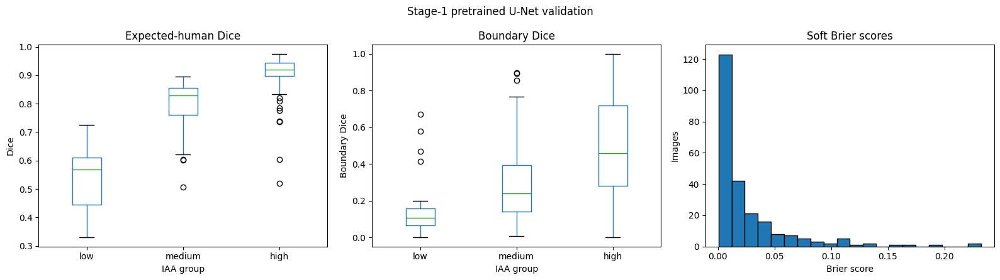


COMPREHENSIVE STAGE-1 VALIDATION EVALUATION COMPLETE
Images evaluated: 240
Checkpoint epoch: 15

Segmentation:
Expected-human Dice: 0.847626
Expected-human IoU: 0.760542
Consensus Dice: 0.852894
STAPLE Dice: 0.849998
Majority Dice: 0.852894

Surface and boundary:
Expected-human HD95: 28.5813 px
Expected-human ASSD: 11.5213 px
Expected-human boundary Dice: 0.419357

Calibration:
Soft Brier: 0.025521
Soft NLL: 0.177988
Soft ECE-15: 0.045450

Efficiency:
Parameters: 1,942,577
GPU latency: 1.062 ms/image
GPU throughput: 941.88 images/second
Peak GPU memory: 1.31 GB

IAA summary:


,iaa_group,images,expected_human_dice,expected_human_iou,expected_human_hd95_px,expected_human_assd_px,expected_human_boundary_dice,consensus_dice,soft_brier,soft_ece_15,entropy_human_disagreement_spearman,entropy_boundary_disagreement_spearman
1,low,24,0.544976,0.410929,84.186625,38.504262,0.167840,0.592751,0.057108,0.117848,0.157657,0.042979
2,medium,58,0.800121,0.682283,37.715924,14.341455,0.304859,0.810005,0.032458,0.058619,0.353380,0.131432
0,high,158,0.911037,0.842375,16.781765,6.387370,0.499593,0.908153,0.018176,0.029618,0.106271,0.244278



Primary bootstrap intervals:


,metric,n,mean,ci95_lower,ci95_upper,bootstrap_repetitions,bootstrap_seed
0,expected_human_dice,240,0.847626,0.831643,0.863618,2000,4201
1,expected_human_iou,240,0.760542,0.739953,0.780246,2000,4201
5,expected_human_hd95_px,240,28.581340,24.484759,32.858602,2000,4201
6,expected_human_assd_px,240,11.521296,9.860207,13.366921,2000,4201
7,expected_human_boundary_dice,240,0.419357,0.384849,0.452604,2000,4201
8,consensus_dice,240,0.852894,0.836058,0.868476,2000,4201
15,soft_brier,240,0.025521,0.020865,0.030768,2000,4201
17,soft_ece_15,240,0.045450,0.037807,0.054086,2000,4201



Evaluation directory: /content/drive/MyDrive/MADSeg/outputs/single_annotator_pretraining_v1/validation_evaluation
Test set remains untouched.


In [ ]:
# ============================================================
# Comprehensive Stage-1 pretrained U-Net VALIDATION evaluation
# Run only AFTER Stage-1 training finishes
# ============================================================

import json
import math
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from pathlib import Path
from scipy.ndimage import binary_dilation
from tqdm.auto import tqdm


# Confirm that the common locked evaluator definitions exist
required_evaluation_functions = [
    "overlap_metrics",
    "surface_distance_metrics",
    "boundary_dice",
    "complete_binary_metrics",
    "prefix_metrics",
    "soft_brier_score",
    "soft_nll",
    "soft_ece",
    "normalized_entropy",
    "correlation_inside_roi",
]

for function_name in required_evaluation_functions:
    assert function_name in globals(), (
        f"{function_name} is missing. Rerun the earlier "
        f"comprehensive U-Net evaluation-definition cell."
    )


# ------------------------------------------------------------
# 1. Paths and locked protocol
# ------------------------------------------------------------

STAGE1_EVALUATION_DIR = (
    PRETRAIN_RUN_DIR / "validation_evaluation"
)
STAGE1_EVALUATION_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

STAGE1_PER_IMAGE_CSV = (
    STAGE1_EVALUATION_DIR / "per_image_metrics.csv"
)
STAGE1_SUMMARY_CSV = (
    STAGE1_EVALUATION_DIR / "metric_summary.csv"
)
STAGE1_BOOTSTRAP_CSV = (
    STAGE1_EVALUATION_DIR / "bootstrap_95ci.csv"
)
STAGE1_IAA_CSV = (
    STAGE1_EVALUATION_DIR / "metrics_by_iaa_group.csv"
)
STAGE1_K_CSV = (
    STAGE1_EVALUATION_DIR
    / "metrics_by_annotation_count.csv"
)
STAGE1_CLINICAL_CSV = (
    STAGE1_EVALUATION_DIR
    / "clinical_subgroup_summary.csv"
)
STAGE1_EFFICIENCY_JSON = (
    STAGE1_EVALUATION_DIR / "efficiency.json"
)
STAGE1_PROTOCOL_JSON = (
    STAGE1_EVALUATION_DIR / "evaluation_protocol.json"
)
STAGE1_FIGURE_PATH = (
    STAGE1_EVALUATION_DIR / "validation_overview.png"
)

PREDICTION_THRESHOLD = 0.5
BOUNDARY_TOLERANCE_PX = 2
ROI_DILATION_PX = 5
ECE_BINS = 15
BOOTSTRAP_REPETITIONS = 2000
BOOTSTRAP_SEED = 4201

assert PRETRAIN_BEST_CHECKPOINT.exists(), (
    "Stage-1 best checkpoint does not exist. "
    "Finish Stage-1 training first."
)


# ------------------------------------------------------------
# 2. Load the best Stage-1 checkpoint
# ------------------------------------------------------------

stage1_best_checkpoint = torch.load(
    PRETRAIN_BEST_CHECKPOINT,
    map_location=DEVICE,
    weights_only=False,
)

stage1_evaluation_model = UNet(
    in_channels=3,
    out_channels=1,
    base_channels=16,
).to(DEVICE)

stage1_evaluation_model.load_state_dict(
    stage1_best_checkpoint["model_state"]
)
stage1_evaluation_model.eval()

stage1_parameter_count = sum(
    parameter.numel()
    for parameter in stage1_evaluation_model.parameters()
)

assert stage1_parameter_count == 1_942_577


# ------------------------------------------------------------
# 3. GPU warm-up
# ------------------------------------------------------------

with torch.inference_mode():
    warmup_image = torch.zeros(
        1,
        3,
        352,
        352,
        device=DEVICE,
    )

    for _ in range(3):
        with torch.autocast(
            device_type="cuda",
            dtype=AMP_DTYPE,
        ):
            _ = stage1_evaluation_model(warmup_image)

torch.cuda.synchronize()
torch.cuda.reset_peak_memory_stats()


# ------------------------------------------------------------
# 4. Per-image evaluation
# ------------------------------------------------------------

stage1_records = []
stage1_total_inference_ms = 0.0
stage1_evaluated_images = 0

with torch.inference_mode():
    for evaluation_batch in tqdm(
        validation_loader,
        desc="Stage-1 full validation evaluation",
    ):
        images_gpu = evaluation_batch["image"].to(
            DEVICE,
            non_blocking=True,
        )

        start_event = torch.cuda.Event(enable_timing=True)
        end_event = torch.cuda.Event(enable_timing=True)

        start_event.record()

        with torch.autocast(
            device_type="cuda",
            dtype=AMP_DTYPE,
        ):
            logits = stage1_evaluation_model(images_gpu)

        end_event.record()
        torch.cuda.synchronize()

        stage1_total_inference_ms += (
            start_event.elapsed_time(end_event)
        )

        probabilities = torch.sigmoid(
            logits.float()
        ).cpu().numpy()[:, 0]

        batch_size = probabilities.shape[0]
        stage1_evaluated_images += batch_size

        for sample_index in range(batch_size):
            probability = probabilities[sample_index]
            prediction = probability >= PREDICTION_THRESHOLD

            mask_valid = (
                evaluation_batch["mask_valid"][sample_index]
                .numpy()
                .astype(bool)
            )

            boundary_valid = (
                evaluation_batch["boundary_valid"][sample_index]
                .numpy()
                .astype(bool)
            )

            all_padded_human_masks = (
                evaluation_batch["human_masks"][sample_index]
                .numpy()
            )

            human_masks = (
                all_padded_human_masks[mask_valid] > 0.5
            )

            boundary_valid_humans = (
                all_padded_human_masks[boundary_valid] > 0.5
            )

            soft_target = (
                evaluation_batch[
                    "soft_consensus"
                ][sample_index, 0].numpy()
            )

            hard_target = (
                evaluation_batch[
                    "hard_consensus"
                ][sample_index, 0].numpy()
                > 0.5
            )

            staple_target = (
                evaluation_batch[
                    "staple_mask"
                ][sample_index, 0].numpy()
                > 0.5
            )

            majority_target = (
                evaluation_batch[
                    "majority_mask"
                ][sample_index, 0].numpy()
                > 0.5
            )

            human_disagreement = (
                evaluation_batch[
                    "human_disagreement"
                ][sample_index, 0].numpy()
            )

            boundary_disagreement = (
                evaluation_batch[
                    "boundary_disagreement"
                ][sample_index, 0].numpy()
            )

            consensus_boundary = (
                evaluation_batch[
                    "consensus_boundary"
                ][sample_index, 0].numpy()
                > 0.5
            )

            predictive_entropy = normalized_entropy(
                probability
            )

            record = {
                "iaa_id": int(
                    evaluation_batch[
                        "iaa_id"
                    ][sample_index]
                ),
                "isic_id": evaluation_batch[
                    "isic_id"
                ][sample_index],
                "split": evaluation_batch[
                    "split"
                ][sample_index],
                "iaa_group": evaluation_batch[
                    "iaa_group"
                ][sample_index],
                "num_human_masks": int(mask_valid.sum()),
            }

            # Expected metrics against individual humans
            individual_overlap = [
                overlap_metrics(prediction, human_target)
                for human_target in human_masks
            ]

            for metric_name in [
                "dice",
                "iou",
                "precision",
                "recall",
                "specificity",
                "accuracy",
            ]:
                record[
                    f"expected_human_{metric_name}"
                ] = float(np.mean([
                    result[metric_name]
                    for result in individual_overlap
                ]))

            if len(boundary_valid_humans) > 0:
                individual_surface = [
                    surface_distance_metrics(
                        prediction,
                        human_target,
                    )
                    for human_target in boundary_valid_humans
                ]

                record["expected_human_hd95_px"] = float(
                    np.mean([
                        result["hd95_px"]
                        for result in individual_surface
                    ])
                )

                record["expected_human_assd_px"] = float(
                    np.mean([
                        result["assd_px"]
                        for result in individual_surface
                    ])
                )

                record[
                    "expected_human_boundary_dice"
                ] = float(np.mean([
                    boundary_dice(
                        prediction,
                        human_target,
                    )
                    for human_target in boundary_valid_humans
                ]))
            else:
                record["expected_human_hd95_px"] = np.nan
                record["expected_human_assd_px"] = np.nan
                record[
                    "expected_human_boundary_dice"
                ] = np.nan

            for target_name, target in [
                ("consensus", hard_target),
                ("staple", staple_target),
                ("majority", majority_target),
            ]:
                record.update(prefix_metrics(
                    complete_binary_metrics(
                        prediction,
                        target,
                    ),
                    target_name,
                ))

            # Calibration against soft consensus
            record["soft_brier"] = soft_brier_score(
                probability,
                soft_target,
            )
            record["soft_nll"] = soft_nll(
                probability,
                soft_target,
            )
            record["soft_ece_15"] = soft_ece(
                probability,
                soft_target,
                ECE_BINS,
            )
            record["mean_predictive_entropy"] = float(
                predictive_entropy.mean()
            )

            # Entropy-disagreement alignment
            human_union = np.any(human_masks, axis=0)

            lesion_roi = binary_dilation(
                human_union,
                iterations=ROI_DILATION_PX,
            )

            boundary_roi = binary_dilation(
                consensus_boundary,
                iterations=ROI_DILATION_PX,
            )

            lesion_pearson, lesion_spearman = (
                correlation_inside_roi(
                    predictive_entropy,
                    human_disagreement,
                    lesion_roi,
                )
            )

            boundary_pearson, boundary_spearman = (
                correlation_inside_roi(
                    predictive_entropy,
                    boundary_disagreement,
                    boundary_roi,
                )
            )

            record[
                "entropy_human_disagreement_pearson"
            ] = lesion_pearson
            record[
                "entropy_human_disagreement_spearman"
            ] = lesion_spearman
            record[
                "entropy_boundary_disagreement_pearson"
            ] = boundary_pearson
            record[
                "entropy_boundary_disagreement_spearman"
            ] = boundary_spearman

            stage1_records.append(record)


assert stage1_evaluated_images == 240
assert all(
    record["split"] == "validation"
    for record in stage1_records
)

stage1_per_image = pd.DataFrame(stage1_records)


# ------------------------------------------------------------
# 5. Merge available clinical metadata
# ------------------------------------------------------------

clinical_columns = [
    "isic_id",
    "age_approx",
    "sex",
    "anatom_site_general",
    "benign_malignant",
    "diagnosis_1",
    "diagnosis_2",
    "diagnosis_3",
]

available_clinical_columns = [
    column
    for column in clinical_columns
    if column in canonical_manifest.columns
]

clinical_metadata = (
    canonical_manifest[available_clinical_columns]
    .drop_duplicates(subset=["isic_id"])
)

stage1_per_image = stage1_per_image.merge(
    clinical_metadata,
    on="isic_id",
    how="left",
    validate="one_to_one",
)

stage1_per_image.to_csv(
    STAGE1_PER_IMAGE_CSV,
    index=False,
)


# ------------------------------------------------------------
# 6. Overall metric summary
# ------------------------------------------------------------

identifier_columns = {
    "iaa_id",
    "isic_id",
    "split",
    "iaa_group",
    "num_human_masks",
    "age_approx",
    "sex",
    "anatom_site_general",
    "benign_malignant",
    "diagnosis_1",
    "diagnosis_2",
    "diagnosis_3",
}

metric_columns = [
    column
    for column in stage1_per_image.columns
    if column not in identifier_columns
    and pd.api.types.is_numeric_dtype(
        stage1_per_image[column]
    )
]

stage1_summary_rows = []

for metric_name in metric_columns:
    values = stage1_per_image[metric_name].dropna()

    stage1_summary_rows.append({
        "metric": metric_name,
        "n": len(values),
        "mean": values.mean(),
        "std": values.std(ddof=1),
        "median": values.median(),
        "minimum": values.min(),
        "maximum": values.max(),
    })

stage1_metric_summary = pd.DataFrame(
    stage1_summary_rows
)

stage1_metric_summary.to_csv(
    STAGE1_SUMMARY_CSV,
    index=False,
)


# ------------------------------------------------------------
# 7. Bootstrap 95% confidence intervals
# ------------------------------------------------------------

bootstrap_metrics = [
    "expected_human_dice",
    "expected_human_iou",
    "expected_human_precision",
    "expected_human_recall",
    "expected_human_specificity",
    "expected_human_hd95_px",
    "expected_human_assd_px",
    "expected_human_boundary_dice",
    "consensus_dice",
    "consensus_iou",
    "consensus_hd95_px",
    "consensus_assd_px",
    "consensus_boundary_dice",
    "staple_dice",
    "majority_dice",
    "soft_brier",
    "soft_nll",
    "soft_ece_15",
    "entropy_human_disagreement_spearman",
    "entropy_boundary_disagreement_spearman",
]

bootstrap_rng = np.random.default_rng(
    BOOTSTRAP_SEED
)

stage1_bootstrap_rows = []

for metric_name in bootstrap_metrics:
    values = (
        stage1_per_image[metric_name]
        .dropna()
        .to_numpy(dtype=np.float64)
    )

    sampled_indices = bootstrap_rng.integers(
        0,
        len(values),
        size=(
            BOOTSTRAP_REPETITIONS,
            len(values),
        ),
    )

    sampled_means = values[
        sampled_indices
    ].mean(axis=1)

    stage1_bootstrap_rows.append({
        "metric": metric_name,
        "n": len(values),
        "mean": values.mean(),
        "ci95_lower": np.percentile(
            sampled_means,
            2.5,
        ),
        "ci95_upper": np.percentile(
            sampled_means,
            97.5,
        ),
        "bootstrap_repetitions": (
            BOOTSTRAP_REPETITIONS
        ),
        "bootstrap_seed": BOOTSTRAP_SEED,
    })

stage1_bootstrap = pd.DataFrame(
    stage1_bootstrap_rows
)

stage1_bootstrap.to_csv(
    STAGE1_BOOTSTRAP_CSV,
    index=False,
)


# ------------------------------------------------------------
# 8. IAA and annotation-count summaries
# ------------------------------------------------------------

reported_group_metrics = [
    "expected_human_dice",
    "expected_human_iou",
    "expected_human_hd95_px",
    "expected_human_assd_px",
    "expected_human_boundary_dice",
    "consensus_dice",
    "soft_brier",
    "soft_ece_15",
    "entropy_human_disagreement_spearman",
    "entropy_boundary_disagreement_spearman",
]

stage1_iaa_summary = (
    stage1_per_image
    .groupby("iaa_group", dropna=False)
    .agg(
        images=("isic_id", "count"),
        **{
            metric: (metric, "mean")
            for metric in reported_group_metrics
        },
    )
    .reset_index()
)

stage1_iaa_summary["iaa_group"] = pd.Categorical(
    stage1_iaa_summary["iaa_group"],
    categories=["low", "medium", "high"],
    ordered=True,
)

stage1_iaa_summary = (
    stage1_iaa_summary.sort_values("iaa_group")
)

stage1_iaa_summary.to_csv(
    STAGE1_IAA_CSV,
    index=False,
)

stage1_k_summary = (
    stage1_per_image
    .groupby("num_human_masks", dropna=False)
    .agg(
        images=("isic_id", "count"),
        **{
            metric: (metric, "mean")
            for metric in reported_group_metrics
        },
    )
    .reset_index()
)

stage1_k_summary.to_csv(
    STAGE1_K_CSV,
    index=False,
)


# ------------------------------------------------------------
# 9. Clinical subgroup summary
# ------------------------------------------------------------

clinical_rows = []

for group_column in [
    "sex",
    "anatom_site_general",
    "benign_malignant",
    "diagnosis_1",
]:
    if group_column not in stage1_per_image.columns:
        continue

    for group_value, group_frame in (
        stage1_per_image.groupby(
            group_column,
            dropna=True,
        )
    ):
        if len(group_frame) < 5:
            continue

        clinical_rows.append({
            "group_variable": group_column,
            "group_value": group_value,
            "images": len(group_frame),
            "expected_human_dice": group_frame[
                "expected_human_dice"
            ].mean(),
            "expected_human_iou": group_frame[
                "expected_human_iou"
            ].mean(),
            "expected_human_hd95_px": group_frame[
                "expected_human_hd95_px"
            ].mean(),
            "expected_human_boundary_dice": group_frame[
                "expected_human_boundary_dice"
            ].mean(),
            "soft_brier": group_frame[
                "soft_brier"
            ].mean(),
        })

stage1_clinical_summary = pd.DataFrame(
    clinical_rows
)
stage1_clinical_summary.to_csv(
    STAGE1_CLINICAL_CSV,
    index=False,
)


# ------------------------------------------------------------
# 10. Efficiency and protocol
# ------------------------------------------------------------

stage1_mean_latency_ms = (
    stage1_total_inference_ms
    / stage1_evaluated_images
)

stage1_throughput = (
    stage1_evaluated_images
    / (stage1_total_inference_ms / 1000.0)
)

stage1_peak_memory_gb = (
    torch.cuda.max_memory_allocated() / 1024**3
)

stage1_efficiency = {
    "model": "Stage-1 pretrained UNet",
    "parameters": stage1_parameter_count,
    "resolution": [352, 352],
    "batch_size": validation_loader.batch_size,
    "images": stage1_evaluated_images,
    "gpu": torch.cuda.get_device_name(0),
    "amp_dtype": str(AMP_DTYPE),
    "gpu_only_latency_ms_per_image": (
        stage1_mean_latency_ms
    ),
    "gpu_only_images_per_second": (
        stage1_throughput
    ),
    "peak_allocated_gpu_memory_gb": (
        stage1_peak_memory_gb
    ),
    "gflops": None,
}

with open(
    STAGE1_EFFICIENCY_JSON,
    "w",
    encoding="utf-8",
) as file:
    json.dump(stage1_efficiency, file, indent=2)

stage1_protocol = {
    "run_name": PRETRAIN_RUN_NAME,
    "checkpoint_epoch": int(
        stage1_best_checkpoint["epoch"]
    ),
    "evaluation_split": "validation",
    "test_set_evaluated": False,
    "prediction_threshold": PREDICTION_THRESHOLD,
    "boundary_tolerance_px": BOUNDARY_TOLERANCE_PX,
    "surface_distance_units": "352x352 pixels",
    "ece_bins": ECE_BINS,
    "uncertainty_proxy": (
        "normalized sigmoid predictive entropy"
    ),
    "roi_dilation_px": ROI_DILATION_PX,
    "bootstrap_repetitions": BOOTSTRAP_REPETITIONS,
    "bootstrap_seed": BOOTSTRAP_SEED,
}

with open(
    STAGE1_PROTOCOL_JSON,
    "w",
    encoding="utf-8",
) as file:
    json.dump(stage1_protocol, file, indent=2)


# ------------------------------------------------------------
# 11. Overview figure
# ------------------------------------------------------------

figure, axes = plt.subplots(
    1,
    3,
    figsize=(16, 4.5),
)

plot_frame = stage1_per_image.copy()
plot_frame["iaa_group"] = pd.Categorical(
    plot_frame["iaa_group"],
    categories=["low", "medium", "high"],
    ordered=True,
)

plot_frame.boxplot(
    column="expected_human_dice",
    by="iaa_group",
    ax=axes[0],
    grid=False,
)
axes[0].set_title("Expected-human Dice")
axes[0].set_xlabel("IAA group")
axes[0].set_ylabel("Dice")

plot_frame.boxplot(
    column="expected_human_boundary_dice",
    by="iaa_group",
    ax=axes[1],
    grid=False,
)
axes[1].set_title("Boundary Dice")
axes[1].set_xlabel("IAA group")
axes[1].set_ylabel("Boundary Dice")

axes[2].hist(
    stage1_per_image["soft_brier"],
    bins=20,
    edgecolor="black",
)
axes[2].set_title("Soft Brier scores")
axes[2].set_xlabel("Brier score")
axes[2].set_ylabel("Images")

figure.suptitle(
    "Stage-1 pretrained U-Net validation",
)
figure.tight_layout()
figure.savefig(
    STAGE1_FIGURE_PATH,
    dpi=180,
    bbox_inches="tight",
)
plt.show()
plt.close(figure)


# ------------------------------------------------------------
# 12. Essential report
# ------------------------------------------------------------

def stage1_mean(metric):
    return float(
        stage1_metric_summary.loc[
            stage1_metric_summary["metric"] == metric,
            "mean",
        ].iloc[0]
    )


print(
    "\nCOMPREHENSIVE STAGE-1 VALIDATION EVALUATION COMPLETE"
)
print(f"Images evaluated: {stage1_evaluated_images}")
print(
    "Checkpoint epoch:",
    stage1_best_checkpoint["epoch"],
)

print("\nSegmentation:")
print(
    "Expected-human Dice:",
    f"{stage1_mean('expected_human_dice'):.6f}",
)
print(
    "Expected-human IoU:",
    f"{stage1_mean('expected_human_iou'):.6f}",
)
print(
    "Consensus Dice:",
    f"{stage1_mean('consensus_dice'):.6f}",
)
print(
    "STAPLE Dice:",
    f"{stage1_mean('staple_dice'):.6f}",
)
print(
    "Majority Dice:",
    f"{stage1_mean('majority_dice'):.6f}",
)

print("\nSurface and boundary:")
print(
    "Expected-human HD95:",
    f"{stage1_mean('expected_human_hd95_px'):.4f} px",
)
print(
    "Expected-human ASSD:",
    f"{stage1_mean('expected_human_assd_px'):.4f} px",
)
print(
    "Expected-human boundary Dice:",
    f"{stage1_mean('expected_human_boundary_dice'):.6f}",
)

print("\nCalibration:")
print(
    "Soft Brier:",
    f"{stage1_mean('soft_brier'):.6f}",
)
print(
    "Soft NLL:",
    f"{stage1_mean('soft_nll'):.6f}",
)
print(
    "Soft ECE-15:",
    f"{stage1_mean('soft_ece_15'):.6f}",
)

print("\nEfficiency:")
print(f"Parameters: {stage1_parameter_count:,}")
print(
    "GPU latency:",
    f"{stage1_mean_latency_ms:.3f} ms/image",
)
print(
    "GPU throughput:",
    f"{stage1_throughput:.2f} images/second",
)
print(
    "Peak GPU memory:",
    f"{stage1_peak_memory_gb:.2f} GB",
)

print("\nIAA summary:")
display(stage1_iaa_summary.round(6))

print("\nPrimary bootstrap intervals:")
display(
    stage1_bootstrap[
        stage1_bootstrap["metric"].isin([
            "expected_human_dice",
            "expected_human_iou",
            "expected_human_hd95_px",
            "expected_human_assd_px",
            "expected_human_boundary_dice",
            "consensus_dice",
            "soft_brier",
            "soft_ece_15",
        ])
    ].round(6)
)

print("\nEvaluation directory:", STAGE1_EVALUATION_DIR)
print("Test set remains untouched.")

In [ ]:
# ============================================================
# Paired validation comparison:
# Direct U-Net versus Stage-1 pretrained U-Net
# ============================================================

import numpy as np
import pandas as pd

from pathlib import Path


DIRECT_RESULTS = Path(
    "/content/drive/MyDrive/MADSeg/outputs/"
    "unet_soft_consensus_baseline_v1/"
    "validation_evaluation/per_image_metrics.csv"
)

PRETRAINED_RESULTS = Path(
    "/content/drive/MyDrive/MADSeg/outputs/"
    "single_annotator_pretraining_v1/"
    "validation_evaluation/per_image_metrics.csv"
)

COMPARISON_DIR = Path(
    "/content/drive/MyDrive/MADSeg/outputs/"
    "model_comparisons"
)
COMPARISON_DIR.mkdir(parents=True, exist_ok=True)

COMPARISON_CSV = (
    COMPARISON_DIR
    / "stage1_pretrained_vs_direct_unet_validation.csv"
)

direct_results = pd.read_csv(DIRECT_RESULTS)
pretrained_results = pd.read_csv(PRETRAINED_RESULTS)

assert len(direct_results) == 240
assert len(pretrained_results) == 240
assert direct_results["isic_id"].is_unique
assert pretrained_results["isic_id"].is_unique

paired = direct_results.merge(
    pretrained_results,
    on="isic_id",
    suffixes=("_direct", "_pretrained"),
    validate="one_to_one",
)

assert len(paired) == 240

comparison_metrics = {
    # Higher is better
    "expected_human_dice": "higher",
    "expected_human_iou": "higher",
    "expected_human_boundary_dice": "higher",
    "consensus_dice": "higher",
    "staple_dice": "higher",
    "majority_dice": "higher",
    "entropy_human_disagreement_spearman": "higher",
    "entropy_boundary_disagreement_spearman": "higher",

    # Lower is better
    "expected_human_hd95_px": "lower",
    "expected_human_assd_px": "lower",
    "soft_brier": "lower",
    "soft_nll": "lower",
    "soft_ece_15": "lower",
}

PAIRED_BOOTSTRAPS = 5000
PAIRED_SEED = 4202
paired_rng = np.random.default_rng(PAIRED_SEED)

comparison_rows = []

for metric, favorable_direction in comparison_metrics.items():
    direct = paired[
        f"{metric}_direct"
    ].to_numpy(dtype=np.float64)

    pretrained = paired[
        f"{metric}_pretrained"
    ].to_numpy(dtype=np.float64)

    finite = np.isfinite(direct) & np.isfinite(pretrained)
    direct = direct[finite]
    pretrained = pretrained[finite]

    raw_difference = pretrained - direct

    # Positive favorable_difference always means improvement.
    if favorable_direction == "higher":
        favorable_difference = raw_difference
    else:
        favorable_difference = -raw_difference

    bootstrap_indices = paired_rng.integers(
        0,
        len(favorable_difference),
        size=(PAIRED_BOOTSTRAPS, len(favorable_difference)),
    )

    bootstrap_improvements = favorable_difference[
        bootstrap_indices
    ].mean(axis=1)

    probability_nonpositive = np.mean(
        bootstrap_improvements <= 0
    )
    probability_nonnegative = np.mean(
        bootstrap_improvements >= 0
    )

    two_sided_bootstrap_p = min(
        1.0,
        2.0 * min(
            probability_nonpositive,
            probability_nonnegative,
        ),
    )

    comparison_rows.append({
        "metric": metric,
        "n_paired": len(favorable_difference),
        "direct_mean": direct.mean(),
        "pretrained_mean": pretrained.mean(),
        "raw_delta_pretrained_minus_direct": (
            raw_difference.mean()
        ),
        "favorable_direction": favorable_direction,
        "mean_favorable_improvement": (
            favorable_difference.mean()
        ),
        "improvement_ci95_lower": np.percentile(
            bootstrap_improvements,
            2.5,
        ),
        "improvement_ci95_upper": np.percentile(
            bootstrap_improvements,
            97.5,
        ),
        "bootstrap_two_sided_p": (
            two_sided_bootstrap_p
        ),
        "bootstrap_repetitions": PAIRED_BOOTSTRAPS,
        "bootstrap_seed": PAIRED_SEED,
    })

paired_comparison = pd.DataFrame(comparison_rows)
paired_comparison.to_csv(COMPARISON_CSV, index=False)

print("PAIRED VALIDATION COMPARISON COMPLETE")
print("Positive favorable improvement means Stage 1 is better.")
print()

display(
    paired_comparison[
        [
            "metric",
            "direct_mean",
            "pretrained_mean",
            "raw_delta_pretrained_minus_direct",
            "mean_favorable_improvement",
            "improvement_ci95_lower",
            "improvement_ci95_upper",
            "bootstrap_two_sided_p",
        ]
    ].round(6)
)

print("\nSaved:", COMPARISON_CSV)
print("Test set remains untouched.")

PAIRED VALIDATION COMPARISON COMPLETE
Positive favorable improvement means Stage 1 is better.



,metric,direct_mean,pretrained_mean,raw_delta_pretrained_minus_direct,mean_favorable_improvement,improvement_ci95_lower,improvement_ci95_upper,bootstrap_two_sided_p
0,expected_human_dice,0.840225,0.847626,0.007401,0.007401,-0.000434,0.016295,0.0656
1,expected_human_iou,0.750428,0.760542,0.010114,0.010114,0.000461,0.019978,0.0420
2,expected_human_boundary_dice,0.399895,0.419357,0.019462,0.019462,0.005657,0.033510,0.0076
3,consensus_dice,0.841817,0.852894,0.011077,0.011077,-0.000622,0.023184,0.0692
4,staple_dice,0.846173,0.849998,0.003825,0.003825,-0.007784,0.015456,0.5212
5,majority_dice,0.841817,0.852894,0.011077,0.011077,-0.000948,0.023558,0.0700
6,entropy_human_disagreement_spearman,0.172791,0.171128,-0.001663,-0.001663,-0.020826,0.017139,0.8688
7,entropy_boundary_disagreement_spearman,0.186068,0.196877,0.010809,0.010809,-0.004245,0.025751,0.1608
8,expected_human_hd95_px,30.130462,28.581340,-1.549122,1.549122,-1.015317,4.591616,0.2644
9,expected_human_assd_px,11.881987,11.521296,-0.360690,0.360690,-0.486314,1.223260,0.3984



Saved: /content/drive/MyDrive/MADSeg/outputs/model_comparisons/stage1_pretrained_vs_direct_unet_validation.csv
Test set remains untouched.


# STAGE 2

In [ ]:
# ============================================================
# Transfer Stage-1 checkpoint into MAD-Seg
# ============================================================

import json
import torch
import torch.nn as nn

from pathlib import Path
from madseg_model import MADSeg


STAGE2_INITIALIZATION_DIR = (
    Path("/content/drive/MyDrive/MADSeg/outputs")
    / "madseg_stage2_initialization"
)
STAGE2_INITIALIZATION_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

STAGE2_INITIALIZATION_CHECKPOINT = (
    STAGE2_INITIALIZATION_DIR
    / "madseg_stage2_initialization.pt"
)

assert PRETRAIN_BEST_CHECKPOINT.exists()


# ------------------------------------------------------------
# 1. Load locked Stage-1 model
# ------------------------------------------------------------

stage1_checkpoint = torch.load(
    PRETRAIN_BEST_CHECKPOINT,
    map_location=DEVICE,
    weights_only=False,
)

stage1_reference_model = UNet(
    in_channels=3,
    out_channels=1,
    base_channels=16,
).to(DEVICE)

stage1_reference_model.load_state_dict(
    stage1_checkpoint["model_state"]
)
stage1_reference_model.eval()

assert int(stage1_checkpoint["epoch"]) == 15


# ------------------------------------------------------------
# 2. Create fresh MAD-Seg
# ------------------------------------------------------------

torch.manual_seed(SEED + 300)
torch.cuda.manual_seed_all(SEED + 300)

stage2_model = MADSeg(
    in_channels=3,
    base_channels=16,
    number_of_annotators=len(ANNOTATOR_TO_ID),
    number_of_tools=len(TOOL_TO_ID),
    number_of_skills=len(SKILL_TO_ID),
    embedding_dimension=8,
).to(DEVICE)

source_state = stage1_reference_model.state_dict()
target_state = stage2_model.state_dict()

transferred_pairs = []


# ------------------------------------------------------------
# 3. Transfer shared encoder
# ------------------------------------------------------------

encoder_prefixes = [
    "encoder1.",
    "encoder2.",
    "encoder3.",
    "encoder4.",
    "bottleneck.",
]

for source_key, source_value in source_state.items():
    if any(
        source_key.startswith(prefix)
        for prefix in encoder_prefixes
    ):
        target_key = f"encoder.{source_key}"

        assert target_key in target_state
        assert (
            target_state[target_key].shape
            == source_value.shape
        )

        target_state[target_key] = source_value.clone()
        transferred_pairs.append(
            (source_key, target_key)
        )


# ------------------------------------------------------------
# 4. Transfer segmentation decoder
# ------------------------------------------------------------

decoder_prefixes = [
    "up4.",
    "decoder4.",
    "up3.",
    "decoder3.",
    "up2.",
    "decoder2.",
    "up1.",
    "decoder1.",
]

for source_key, source_value in source_state.items():
    if any(
        source_key.startswith(prefix)
        for prefix in decoder_prefixes
    ):
        target_key = (
            f"consensus_decoder.{source_key}"
        )

        assert target_key in target_state
        assert (
            target_state[target_key].shape
            == source_value.shape
        )

        target_state[target_key] = source_value.clone()
        transferred_pairs.append(
            (source_key, target_key)
        )


# ------------------------------------------------------------
# 5. Transfer output head to raw consensus head
# ------------------------------------------------------------

for source_key, source_value in source_state.items():
    if source_key.startswith("output."):
        suffix = source_key.removeprefix("output.")
        target_key = f"raw_consensus_head.{suffix}"

        assert target_key in target_state
        assert (
            target_state[target_key].shape
            == source_value.shape
        )

        target_state[target_key] = source_value.clone()
        transferred_pairs.append(
            (source_key, target_key)
        )


stage2_model.load_state_dict(target_state)


# ------------------------------------------------------------
# 6. Initialize auxiliary branches
# ------------------------------------------------------------

# Start the ambiguity decoder from learned segmentation features.
stage2_model.ambiguity_decoder.load_state_dict(
    stage2_model.consensus_decoder.state_dict()
)

# Start individual-annotator predictions from the learned
# consensus segmentation head.
stage2_model.annotator_head.load_state_dict(
    stage2_model.raw_consensus_head.state_dict()
)

# Start auxiliary probability heads with conservative outputs.
nn.init.normal_(
    stage2_model.boundary_head.weight,
    mean=0.0,
    std=0.01,
)
nn.init.constant_(
    stage2_model.boundary_head.bias,
    -2.0,
)

nn.init.normal_(
    stage2_model.disagreement_head.weight,
    mean=0.0,
    std=0.01,
)
nn.init.constant_(
    stage2_model.disagreement_head.bias,
    -2.0,
)

# Critical: the fusion branch initially adds zero residual,
# so the initial final mask exactly matches Stage 1.
nn.init.zeros_(
    stage2_model.final_residual_head.weight
)
nn.init.zeros_(
    stage2_model.final_residual_head.bias
)


# ------------------------------------------------------------
# 7. Verify exact output preservation
# ------------------------------------------------------------

verification_batch = next(iter(validation_loader))

verification_images = verification_batch["image"].to(
    DEVICE,
    non_blocking=True,
)

stage2_model.eval()

with torch.inference_mode(), torch.autocast(
    device_type="cuda",
    dtype=AMP_DTYPE,
):
    stage1_logits = stage1_reference_model(
        verification_images
    )

    stage2_outputs = stage2_model(
        verification_images,
        return_annotator_logits=False,
    )

    stage2_logits = stage2_outputs[
        "final_mask_logits"
    ]

maximum_logit_difference = (
    stage1_logits.float()
    - stage2_logits.float()
).abs().max().item()

maximum_probability_difference = (
    torch.sigmoid(stage1_logits.float())
    - torch.sigmoid(stage2_logits.float())
).abs().max().item()

assert maximum_logit_difference < 1e-5
assert maximum_probability_difference < 1e-6


# ------------------------------------------------------------
# 8. Verify complete validation score
# ------------------------------------------------------------

class MADSegFinalMaskWrapper(nn.Module):
    def __init__(self, madseg_model):
        super().__init__()
        self.madseg_model = madseg_model

    def forward(self, image):
        return self.madseg_model(
            image,
            return_annotator_logits=False,
        )["final_mask_logits"]


stage2_wrapper = MADSegFinalMaskWrapper(
    stage2_model
).to(DEVICE)

initial_stage2_validation = validate_model(
    stage2_wrapper,
    validation_loader,
)

stage1_locked_score = 0.847626
stage2_initial_score = initial_stage2_validation[
    "expected_human_dice"
]

score_difference = abs(
    stage2_initial_score - stage1_locked_score
)

assert score_difference < 1e-4


# ------------------------------------------------------------
# 9. Save persistent Stage-2 initialization
# ------------------------------------------------------------

stage2_parameter_count = sum(
    parameter.numel()
    for parameter in stage2_model.parameters()
    if parameter.requires_grad
)

assert stage2_parameter_count == 2_714_749

initialization_record = {
    "model_state": stage2_model.state_dict(),
    "source_checkpoint": str(
        PRETRAIN_BEST_CHECKPOINT
    ),
    "source_epoch": int(stage1_checkpoint["epoch"]),
    "source_validation_expected_human_dice": (
        stage1_locked_score
    ),
    "restored_stage2_validation_metrics": (
        initial_stage2_validation
    ),
    "maximum_logit_difference": (
        maximum_logit_difference
    ),
    "maximum_probability_difference": (
        maximum_probability_difference
    ),
    "parameter_count": stage2_parameter_count,
    "number_of_annotators": len(ANNOTATOR_TO_ID),
    "number_of_tools": len(TOOL_TO_ID),
    "number_of_skills": len(SKILL_TO_ID),
    "transferred_parameter_pairs": transferred_pairs,
    "ambiguity_decoder_initialization": (
        "copied from pretrained consensus decoder"
    ),
    "annotator_head_initialization": (
        "copied from pretrained consensus head"
    ),
    "fusion_residual_initialization": "zeros",
    "boundary_head_bias": -2.0,
    "disagreement_head_bias": -2.0,
    "test_set_evaluated": False,
}

stage1_atomic_save(
    initialization_record,
    STAGE2_INITIALIZATION_CHECKPOINT,
)


# ------------------------------------------------------------
# 10. Report
# ------------------------------------------------------------

print("MAD-Seg Stage-2 initialization passed")
print(f"Source Stage-1 epoch: {stage1_checkpoint['epoch']}")
print(
    "Transferred state tensors:",
    len(transferred_pairs),
)
print(f"MAD-Seg parameters: {stage2_parameter_count:,}")
print(
    "Maximum logit difference:",
    f"{maximum_logit_difference:.10f}",
)
print(
    "Maximum probability difference:",
    f"{maximum_probability_difference:.10f}",
)

print("\nInitial MAD-Seg validation metrics:")
for metric, value in initial_stage2_validation.items():
    print(f"{metric:24s}: {value:.6f}")

print(
    "\nInitialization checkpoint:",
    STAGE2_INITIALIZATION_CHECKPOINT,
)
print("Test set remains untouched.")
print("\nReady for Stage-2 multi-annotator training.")

ModuleNotFoundError: No module named 'madseg_model'

In [ ]:
# ============================================================
# MAD-Seg Stage 2 — Full multi-annotator training
# Maximum 30 epochs, early-stopping patience 5
# ============================================================

import gc
import json
import os
import random
import time

import numpy as np
import pandas as pd
import torch

from pathlib import Path
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
from madseg_model import MADSeg, MADSegLoss


# ------------------------------------------------------------
# 1. Locked configuration
# ------------------------------------------------------------

STAGE2_RUN_NAME = "madseg_stage2_v1"
STAGE2_RUN_DIR = (
    Path("/content/drive/MyDrive/MADSeg/outputs")
    / STAGE2_RUN_NAME
)
STAGE2_RUN_DIR.mkdir(parents=True, exist_ok=True)

STAGE2_LAST_CHECKPOINT = (
    STAGE2_RUN_DIR / "last_checkpoint.pt"
)
STAGE2_BEST_CHECKPOINT = (
    STAGE2_RUN_DIR / "best_checkpoint.pt"
)
STAGE2_HISTORY_CSV = STAGE2_RUN_DIR / "history.csv"
STAGE2_CONFIG_JSON = STAGE2_RUN_DIR / "config.json"

STAGE2_MAX_EPOCHS = 30
STAGE2_PATIENCE = 5
STAGE2_BATCH_SIZE = 16
STAGE2_PRETRAINED_LR = 2e-4
STAGE2_NEW_BRANCH_LR = 1e-3
STAGE2_WEIGHT_DECAY = 1e-4
STAGE2_GRADIENT_CLIP = 1.0
STAGE2_SEED = SEED + 400

STAGE2_LOSS_WEIGHTS = {
    "lambda_segmentation": 1.0,
    "lambda_soft_consensus": 0.5,
    "lambda_boundary": 0.3,
    "lambda_disagreement": 0.3,
    "lambda_annotator": 0.5,
    "lambda_consistency": 0.1,
}

STAGE2_CONFIG = {
    "run_name": STAGE2_RUN_NAME,
    "stage": "multi_annotator_finetuning",
    "initialization": str(
        STAGE2_INITIALIZATION_CHECKPOINT
    ),
    "training_images": len(train_dataset),
    "validation_images": len(validation_dataset),
    "test_images": len(test_dataset),
    "architecture": "MAD-Seg",
    "parameters": 2_714_749,
    "image_size": 352,
    "batch_size": STAGE2_BATCH_SIZE,
    "maximum_epochs": STAGE2_MAX_EPOCHS,
    "early_stopping_patience": STAGE2_PATIENCE,
    "optimizer": "AdamW",
    "pretrained_learning_rate": STAGE2_PRETRAINED_LR,
    "new_branch_learning_rate": STAGE2_NEW_BRANCH_LR,
    "weight_decay": STAGE2_WEIGHT_DECAY,
    "gradient_clip_norm": STAGE2_GRADIENT_CLIP,
    "scheduler": "ReduceLROnPlateau",
    "checkpoint_selection": (
        "validation_expected_human_dice"
    ),
    "loss_weights": STAGE2_LOSS_WEIGHTS,
    "amp_dtype": str(AMP_DTYPE),
    "device": torch.cuda.get_device_name(0),
    "seed": STAGE2_SEED,
    "test_evaluated": False,
}

with open(
    STAGE2_CONFIG_JSON,
    "w",
    encoding="utf-8",
) as file:
    json.dump(STAGE2_CONFIG, file, indent=2)


# ------------------------------------------------------------
# 2. Recreate clean seeded multi-annotator loaders
# ------------------------------------------------------------

for loader_name in ["train_loader", "validation_loader"]:
    if loader_name in globals():
        loader_object = globals()[loader_name]

        try:
            existing_iterator = getattr(
                loader_object,
                "_iterator",
                None,
            )

            if existing_iterator is not None:
                existing_iterator._shutdown_workers()
        except Exception:
            pass

        del globals()[loader_name]

gc.collect()
torch.cuda.empty_cache()

random.seed(STAGE2_SEED)
np.random.seed(STAGE2_SEED)
torch.manual_seed(STAGE2_SEED)
torch.cuda.manual_seed_all(STAGE2_SEED)

stage2_loader_generator = torch.Generator()
stage2_loader_generator.manual_seed(STAGE2_SEED)


def stage2_seed_worker(worker_id):
    worker_seed = STAGE2_SEED + worker_id
    random.seed(worker_seed)
    np.random.seed(worker_seed)
    torch.manual_seed(worker_seed)


stage2_loader_options = {
    "batch_size": STAGE2_BATCH_SIZE,
    "num_workers": NUM_WORKERS,
    "pin_memory": True,
    "persistent_workers": NUM_WORKERS > 0,
    "worker_init_fn": stage2_seed_worker,
}

if NUM_WORKERS > 0:
    stage2_loader_options["prefetch_factor"] = 2

train_loader = DataLoader(
    train_dataset,
    shuffle=True,
    drop_last=False,
    generator=stage2_loader_generator,
    **stage2_loader_options,
)

validation_loader = DataLoader(
    validation_dataset,
    shuffle=False,
    drop_last=False,
    **stage2_loader_options,
)


# ------------------------------------------------------------
# 3. Metric helpers
# ------------------------------------------------------------

def stage2_dice_per_mask(
    prediction,
    target,
    epsilon=1e-6,
):
    prediction = prediction.float()
    target = target.float()

    intersection = (
        prediction * target
    ).sum(dim=(-2, -1))

    denominator = (
        prediction.sum(dim=(-2, -1))
        + target.sum(dim=(-2, -1))
    )

    return (
        2.0 * intersection + epsilon
    ) / (
        denominator + epsilon
    )


def stage2_move_batch(batch):
    tensor_keys = [
        "image",
        "human_masks",
        "mask_valid",
        "boundary_probability",
        "human_disagreement",
        "soft_consensus",
        "hard_consensus",
        "staple_mask",
        "majority_mask",
        "annotator_ids",
        "tool_ids",
        "skill_ids",
    ]

    return {
        key: batch[key].to(
            DEVICE,
            non_blocking=True,
        )
        for key in tensor_keys
    }


@torch.no_grad()
def validate_madseg(model, criterion, loader):
    model.eval()

    image_count = 0
    loss_sums = {
        "total": 0.0,
        "segmentation": 0.0,
        "soft_consensus": 0.0,
        "boundary": 0.0,
        "disagreement": 0.0,
        "annotator": 0.0,
        "consistency": 0.0,
    }

    expected_human_dice_sum = 0.0
    consensus_dice_sum = 0.0
    staple_dice_sum = 0.0
    majority_dice_sum = 0.0
    boundary_dice_sum = 0.0
    disagreement_mae_sum = 0.0
    annotator_dice_sum = 0.0

    for cpu_batch in loader:
        batch = stage2_move_batch(cpu_batch)

        with torch.autocast(
            device_type="cuda",
            dtype=AMP_DTYPE,
        ):
            outputs = model(
                batch["image"],
                annotator_ids=batch["annotator_ids"],
                tool_ids=batch["tool_ids"],
                skill_ids=batch["skill_ids"],
                return_annotator_logits=True,
            )

            losses = criterion(outputs, batch)

        batch_size = batch["image"].shape[0]
        image_count += batch_size

        for name in loss_sums:
            loss_sums[name] += (
                float(losses[name]) * batch_size
            )

        final_prediction = (
            torch.sigmoid(
                outputs["final_mask_logits"].float()
            ) >= 0.5
        ).float()

        expanded_prediction = final_prediction.expand(
            -1,
            batch["human_masks"].shape[1],
            -1,
            -1,
        )

        human_dice = stage2_dice_per_mask(
            expanded_prediction,
            batch["human_masks"],
        )

        human_dice = (
            human_dice * batch["mask_valid"].float()
        )

        expected_human_dice = (
            human_dice.sum(dim=1)
            / batch["mask_valid"]
            .sum(dim=1)
            .clamp_min(1)
        )

        expected_human_dice_sum += float(
            expected_human_dice.sum()
        )

        consensus_dice_sum += float(
            stage2_dice_per_mask(
                final_prediction,
                batch["hard_consensus"],
            ).sum()
        )

        staple_dice_sum += float(
            stage2_dice_per_mask(
                final_prediction,
                batch["staple_mask"],
            ).sum()
        )

        majority_dice_sum += float(
            stage2_dice_per_mask(
                final_prediction,
                batch["majority_mask"],
            ).sum()
        )

        boundary_prediction = (
            torch.sigmoid(
                outputs["boundary_logits"].float()
            ) >= 0.5
        ).float()

        boundary_target = (
            batch["boundary_probability"] >= 0.5
        ).float()

        boundary_dice_sum += float(
            stage2_dice_per_mask(
                boundary_prediction,
                boundary_target,
            ).sum()
        )

        disagreement_probability = torch.sigmoid(
            outputs["disagreement_logits"].float()
        )

        per_image_disagreement_mae = (
            disagreement_probability
            - batch["human_disagreement"]
        ).abs().mean(dim=(1, 2, 3))

        disagreement_mae_sum += float(
            per_image_disagreement_mae.sum()
        )

        annotator_prediction = (
            torch.sigmoid(
                outputs["annotator_logits"].float()
            ) >= 0.5
        ).float()

        annotator_dice = stage2_dice_per_mask(
            annotator_prediction,
            batch["human_masks"],
        )

        annotator_dice = (
            annotator_dice
            * batch["mask_valid"].float()
        )

        per_image_annotator_dice = (
            annotator_dice.sum(dim=1)
            / batch["mask_valid"]
            .sum(dim=1)
            .clamp_min(1)
        )

        annotator_dice_sum += float(
            per_image_annotator_dice.sum()
        )

    result = {
        f"validation_{name}_loss": (
            loss_sums[name] / image_count
        )
        for name in loss_sums
    }

    result.update({
        "expected_human_dice": (
            expected_human_dice_sum / image_count
        ),
        "consensus_dice": (
            consensus_dice_sum / image_count
        ),
        "staple_dice": (
            staple_dice_sum / image_count
        ),
        "majority_dice": (
            majority_dice_sum / image_count
        ),
        "boundary_head_dice": (
            boundary_dice_sum / image_count
        ),
        "disagreement_head_mae": (
            disagreement_mae_sum / image_count
        ),
        "annotator_branch_dice": (
            annotator_dice_sum / image_count
        ),
    })

    return result


# ------------------------------------------------------------
# 4. Safe checkpoint writer
# ------------------------------------------------------------

def stage2_atomic_save(data, destination):
    destination = Path(destination)
    temporary = destination.with_suffix(
        destination.suffix + ".tmp"
    )

    torch.save(data, temporary)
    os.replace(temporary, destination)


# ------------------------------------------------------------
# 5. Create model from exact Stage-2 initialization
# ------------------------------------------------------------

initialization_checkpoint = torch.load(
    STAGE2_INITIALIZATION_CHECKPOINT,
    map_location=DEVICE,
    weights_only=False,
)

madseg_model = MADSeg(
    in_channels=3,
    base_channels=16,
    number_of_annotators=len(ANNOTATOR_TO_ID),
    number_of_tools=len(TOOL_TO_ID),
    number_of_skills=len(SKILL_TO_ID),
    embedding_dimension=8,
).to(DEVICE)

madseg_model.load_state_dict(
    initialization_checkpoint["model_state"]
)

assert sum(
    parameter.numel()
    for parameter in madseg_model.parameters()
    if parameter.requires_grad
) == 2_714_749

madseg_criterion = MADSegLoss(
    **STAGE2_LOSS_WEIGHTS
).to(DEVICE)


# ------------------------------------------------------------
# 6. Differential learning-rate parameter groups
# ------------------------------------------------------------

pretrained_parameters = (
    list(madseg_model.encoder.parameters())
    + list(
        madseg_model.consensus_decoder.parameters()
    )
    + list(
        madseg_model.raw_consensus_head.parameters()
    )
)

new_branch_parameters = (
    list(
        madseg_model.ambiguity_decoder.parameters()
    )
    + list(madseg_model.boundary_head.parameters())
    + list(
        madseg_model.disagreement_head.parameters()
    )
    + list(
        madseg_model.disagreement_fusion.parameters()
    )
    + list(
        madseg_model.final_residual_head.parameters()
    )
    + list(
        madseg_model.metadata_conditioner.parameters()
    )
    + list(madseg_model.annotator_head.parameters())
)

pretrained_parameter_ids = {
    id(parameter)
    for parameter in pretrained_parameters
}
new_parameter_ids = {
    id(parameter)
    for parameter in new_branch_parameters
}

assert pretrained_parameter_ids.isdisjoint(
    new_parameter_ids
)

assert (
    pretrained_parameter_ids | new_parameter_ids
) == {
    id(parameter)
    for parameter in madseg_model.parameters()
    if parameter.requires_grad
}

stage2_optimizer = torch.optim.AdamW(
    [
        {
            "params": pretrained_parameters,
            "lr": STAGE2_PRETRAINED_LR,
            "name": "pretrained",
        },
        {
            "params": new_branch_parameters,
            "lr": STAGE2_NEW_BRANCH_LR,
            "name": "new_branches",
        },
    ],
    weight_decay=STAGE2_WEIGHT_DECAY,
)

stage2_scheduler = (
    torch.optim.lr_scheduler.ReduceLROnPlateau(
        stage2_optimizer,
        mode="max",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
    )
)

stage2_use_scaler = AMP_DTYPE == torch.float16

stage2_scaler = torch.amp.GradScaler(
    "cuda",
    enabled=stage2_use_scaler,
)


# ------------------------------------------------------------
# 7. Fresh start or automatic resume
# ------------------------------------------------------------

stage2_start_epoch = 1
stage2_epochs_without_improvement = 0
stage2_history = []

if STAGE2_LAST_CHECKPOINT.exists():
    checkpoint = torch.load(
        STAGE2_LAST_CHECKPOINT,
        map_location=DEVICE,
        weights_only=False,
    )

    madseg_model.load_state_dict(
        checkpoint["model_state"]
    )
    stage2_optimizer.load_state_dict(
        checkpoint["optimizer_state"]
    )
    stage2_scheduler.load_state_dict(
        checkpoint["scheduler_state"]
    )

    if (
        stage2_use_scaler
        and checkpoint.get("scaler_state") is not None
    ):
        stage2_scaler.load_state_dict(
            checkpoint["scaler_state"]
        )

    stage2_start_epoch = int(
        checkpoint["epoch"]
    ) + 1
    stage2_best_score = float(
        checkpoint["best_validation_score"]
    )
    stage2_epochs_without_improvement = int(
        checkpoint["epochs_without_improvement"]
    )
    stage2_history = checkpoint.get("history", [])

    if checkpoint.get(
        "loader_generator_state"
    ) is not None:
        stage2_loader_generator.set_state(
            checkpoint["loader_generator_state"]
        )

    print(
        f"Resuming Stage 2 from epoch "
        f"{stage2_start_epoch}"
    )
    print(
        "Current best expected-human Dice:",
        f"{stage2_best_score:.6f}",
    )

else:
    print("Evaluating transferred initialization as epoch 0")

    initial_validation = validate_madseg(
        madseg_model,
        madseg_criterion,
        validation_loader,
    )

    stage2_best_score = initial_validation[
        "expected_human_dice"
    ]

    stage2_history = [{
        "epoch": 0,
        "training_total_loss": np.nan,
        **initial_validation,
        "pretrained_learning_rate": (
            STAGE2_PRETRAINED_LR
        ),
        "new_branch_learning_rate": (
            STAGE2_NEW_BRANCH_LR
        ),
        "epoch_seconds": 0.0,
        "improved": True,
        "initialization_only": True,
    }]

    initial_training_checkpoint = {
        "stage": 2,
        "epoch": 0,
        "model_state": madseg_model.state_dict(),
        "optimizer_state": (
            stage2_optimizer.state_dict()
        ),
        "scheduler_state": (
            stage2_scheduler.state_dict()
        ),
        "scaler_state": (
            stage2_scaler.state_dict()
            if stage2_use_scaler
            else None
        ),
        "best_validation_score": stage2_best_score,
        "epochs_without_improvement": 0,
        "history": stage2_history,
        "config": STAGE2_CONFIG,
        "loader_generator_state": (
            stage2_loader_generator.get_state()
        ),
        "source_initialization": str(
            STAGE2_INITIALIZATION_CHECKPOINT
        ),
    }

    pd.DataFrame(stage2_history).to_csv(
        STAGE2_HISTORY_CSV,
        index=False,
    )

    stage2_atomic_save(
        initial_training_checkpoint,
        STAGE2_BEST_CHECKPOINT,
    )
    stage2_atomic_save(
        initial_training_checkpoint,
        STAGE2_LAST_CHECKPOINT,
    )

    print("Epoch 0 validation:")
    for name, value in initial_validation.items():
        print(f"{name:30s}: {value:.6f}")


# ------------------------------------------------------------
# 8. Full Stage-2 training
# ------------------------------------------------------------

stage2_session_start = time.perf_counter()

already_finished = (
    stage2_start_epoch > STAGE2_MAX_EPOCHS
    or stage2_epochs_without_improvement
    >= STAGE2_PATIENCE
)

if already_finished:
    print("Stage 2 was already completed or early-stopped.")

for epoch in range(
    stage2_start_epoch,
    STAGE2_MAX_EPOCHS + 1,
):
    if (
        stage2_epochs_without_improvement
        >= STAGE2_PATIENCE
    ):
        break

    epoch_start = time.perf_counter()
    madseg_model.train()

    training_image_count = 0
    training_loss_sums = {
        "total": 0.0,
        "segmentation": 0.0,
        "soft_consensus": 0.0,
        "boundary": 0.0,
        "disagreement": 0.0,
        "annotator": 0.0,
        "consistency": 0.0,
    }

    progress = tqdm(
        train_loader,
        desc=f"MAD-Seg epoch {epoch:02d}",
        leave=False,
    )

    for cpu_batch in progress:
        batch = stage2_move_batch(cpu_batch)

        stage2_optimizer.zero_grad(set_to_none=True)

        with torch.autocast(
            device_type="cuda",
            dtype=AMP_DTYPE,
        ):
            outputs = madseg_model(
                batch["image"],
                annotator_ids=batch["annotator_ids"],
                tool_ids=batch["tool_ids"],
                skill_ids=batch["skill_ids"],
                return_annotator_logits=True,
            )

            losses = madseg_criterion(
                outputs,
                batch,
            )

        if not torch.isfinite(losses["total"]):
            raise RuntimeError(
                f"Non-finite loss during epoch {epoch}"
            )

        if stage2_use_scaler:
            stage2_scaler.scale(
                losses["total"]
            ).backward()

            stage2_scaler.unscale_(stage2_optimizer)

            torch.nn.utils.clip_grad_norm_(
                madseg_model.parameters(),
                STAGE2_GRADIENT_CLIP,
            )

            stage2_scaler.step(stage2_optimizer)
            stage2_scaler.update()
        else:
            losses["total"].backward()

            torch.nn.utils.clip_grad_norm_(
                madseg_model.parameters(),
                STAGE2_GRADIENT_CLIP,
            )

            stage2_optimizer.step()

        batch_size = batch["image"].shape[0]
        training_image_count += batch_size

        for name in training_loss_sums:
            training_loss_sums[name] += (
                float(losses[name].detach())
                * batch_size
            )

        progress.set_postfix(
            total=f"{float(losses['total']):.4f}",
            seg=f"{float(losses['segmentation']):.4f}",
            boundary=f"{float(losses['boundary']):.4f}",
            disagreement=(
                f"{float(losses['disagreement']):.4f}"
            ),
        )

    mean_training_losses = {
        f"training_{name}_loss": (
            value / training_image_count
        )
        for name, value in training_loss_sums.items()
    }

    validation_metrics = validate_madseg(
        madseg_model,
        madseg_criterion,
        validation_loader,
    )

    selection_score = validation_metrics[
        "expected_human_dice"
    ]

    stage2_scheduler.step(selection_score)

    improved = selection_score > (
        stage2_best_score + 1e-5
    )

    if improved:
        stage2_best_score = selection_score
        stage2_epochs_without_improvement = 0
    else:
        stage2_epochs_without_improvement += 1

    epoch_seconds = time.perf_counter() - epoch_start

    epoch_record = {
        "epoch": epoch,
        **mean_training_losses,
        **validation_metrics,
        "pretrained_learning_rate": (
            stage2_optimizer.param_groups[0]["lr"]
        ),
        "new_branch_learning_rate": (
            stage2_optimizer.param_groups[1]["lr"]
        ),
        "epoch_seconds": epoch_seconds,
        "improved": improved,
        "initialization_only": False,
    }

    stage2_history.append(epoch_record)

    pd.DataFrame(stage2_history).to_csv(
        STAGE2_HISTORY_CSV,
        index=False,
    )

    checkpoint = {
        "stage": 2,
        "epoch": epoch,
        "model_state": madseg_model.state_dict(),
        "optimizer_state": (
            stage2_optimizer.state_dict()
        ),
        "scheduler_state": (
            stage2_scheduler.state_dict()
        ),
        "scaler_state": (
            stage2_scaler.state_dict()
            if stage2_use_scaler
            else None
        ),
        "best_validation_score": stage2_best_score,
        "epochs_without_improvement": (
            stage2_epochs_without_improvement
        ),
        "history": stage2_history,
        "config": STAGE2_CONFIG,
        "loader_generator_state": (
            stage2_loader_generator.get_state()
        ),
        "torch_rng_state": torch.get_rng_state(),
        "cuda_rng_state": torch.cuda.get_rng_state_all(),
        "numpy_rng_state": np.random.get_state(),
        "python_rng_state": random.getstate(),
        "source_initialization": str(
            STAGE2_INITIALIZATION_CHECKPOINT
        ),
    }

    stage2_atomic_save(
        checkpoint,
        STAGE2_LAST_CHECKPOINT,
    )

    if improved:
        stage2_atomic_save(
            checkpoint,
            STAGE2_BEST_CHECKPOINT,
        )

    print(
        f"Epoch {epoch:02d} | "
        f"train {mean_training_losses['training_total_loss']:.5f} | "
        f"val {validation_metrics['validation_total_loss']:.5f} | "
        f"human Dice {selection_score:.5f} | "
        f"consensus {validation_metrics['consensus_dice']:.5f} | "
        f"boundary head {validation_metrics['boundary_head_dice']:.5f} | "
        f"disagreement MAE "
        f"{validation_metrics['disagreement_head_mae']:.5f} | "
        f"annotator Dice "
        f"{validation_metrics['annotator_branch_dice']:.5f} | "
        f"{epoch_seconds:.1f}s"
        + (" | BEST" if improved else "")
    )

    if (
        stage2_epochs_without_improvement
        >= STAGE2_PATIENCE
    ):
        print(
            f"\nStage-2 early stopping at epoch {epoch}: "
            f"no expected-human Dice improvement for "
            f"{STAGE2_PATIENCE} epochs."
        )
        break


# ------------------------------------------------------------
# 9. Completion report
# ------------------------------------------------------------

stage2_session_seconds = (
    time.perf_counter() - stage2_session_start
)

completed_epoch_records = [
    record
    for record in stage2_history
    if record.get("epoch", 0) > 0
]

cumulative_training_seconds = sum(
    record.get("epoch_seconds", 0.0)
    for record in completed_epoch_records
)

best_history_row = max(
    stage2_history,
    key=lambda row: row["expected_human_dice"],
)

print("\nMAD-Seg Stage-2 training finished")
print(
    f"Current session: "
    f"{stage2_session_seconds / 60:.2f} minutes"
)
print(
    f"Cumulative epoch time: "
    f"{cumulative_training_seconds / 60:.2f} minutes"
)
print(f"Best epoch: {best_history_row['epoch']}")
print(
    "Best validation expected-human Dice:",
    f"{stage2_best_score:.6f}",
)
print("Best checkpoint:", STAGE2_BEST_CHECKPOINT)
print("Latest checkpoint:", STAGE2_LAST_CHECKPOINT)
print("History:", STAGE2_HISTORY_CSV)
print("\nTest set remains untouched.")

Evaluating transferred initialization as epoch 0
Epoch 0 validation:
validation_total_loss         : 0.534227
validation_segmentation_loss  : 0.173617
validation_soft_consensus_loss: 0.173617
validation_boundary_loss      : 0.570915
validation_disagreement_loss  : 0.043999
validation_annotator_loss     : 0.178656
validation_consistency_loss   : 0.000000
expected_human_dice           : 0.847626
consensus_dice                : 0.852894
staple_dice                   : 0.849998
majority_dice                 : 0.852894
boundary_head_dice            : 0.000000
disagreement_head_mae         : 0.194240
annotator_branch_dice         : 0.847612


MAD-Seg epoch 01:   0%|          | 0/105 [00:00<?, ?it/s]

Epoch 01 | train 0.52167 | val 0.47580 | human Dice 0.84747 | consensus 0.86604 | boundary head 0.47227 | disagreement MAE 0.15232 | annotator Dice 0.85545 | 89.5s


MAD-Seg epoch 02:   0%|          | 0/105 [00:00<?, ?it/s]

Epoch 02 | train 0.47987 | val 0.45872 | human Dice 0.84780 | consensus 0.84802 | boundary head 0.49474 | disagreement MAE 0.15399 | annotator Dice 0.85579 | 83.6s | BEST


...

Epoch 07 | train 0.45394 | val 0.44590 | human Dice 0.84982 | consensus 0.85114 | boundary head 0.50165 | disagreement MAE 0.13612 | annotator Dice 0.86005 | 84.3s


MAD-Seg epoch 08:   0%|          | 0/105 [00:00<?, ?it/s]

Epoch 08 | train 0.44509 | val 0.44608 | human Dice 0.84856 | consensus 0.84301 | boundary head 0.48555 | disagreement MAE 0.13923 | annotator Dice 0.85878 | 84.7s


MAD-Seg epoch 09:   0%|          | 0/105 [00:00<?, ?it/s]

Epoch 09 | train 0.44259 | val 0.44429 | human Dice 0.84792 | consensus 0.85006 | boundary head 0.48916 | disagreement MAE 0.13223 | annotator Dice 0.85919 | 84.3s

Stage-2 early stopping at epoch 9: no expected-human Dice improvement for 5 epochs.

MAD-Seg Stage-2 training finished
Current session: 12.68 minutes
Cumulative epoch time: 12.66 minutes
Best epoch: 4
Best validation expected-human Dice: 0.850921
Best checkpoint: /content/drive/MyDrive/MADSeg/outputs/madseg_stage2_v1/best_checkpoint.pt
Latest checkpoint: /content/drive/MyDrive/MADSeg/outputs/madseg_stage2_v1/last_checkpoint.pt
History: /content/drive/MyDrive/MADSeg/outputs/madseg_stage2_v1/history.csv

Test set remains untouched.


Comprehensive MAD-Seg validation:   0%|          | 0/15 [00:00<?, ?it/s]

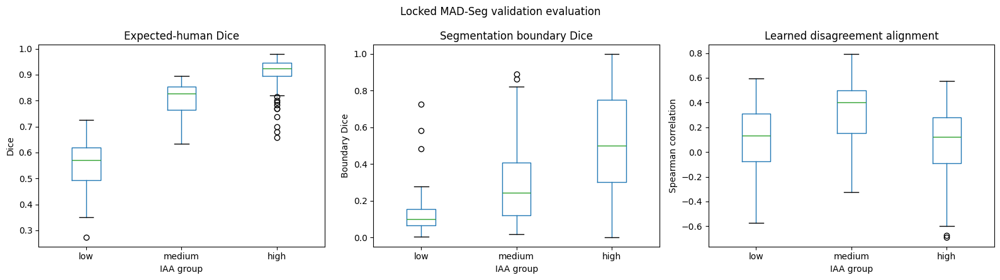


COMPREHENSIVE MAD-SEG VALIDATION COMPLETE
Images evaluated: 240
Checkpoint epoch: 4

Final segmentation:
expected_human_dice                : 0.850921
expected_human_iou                 : 0.764673
consensus_dice                     : 0.856707
staple_dice                        : 0.853739
majority_dice                      : 0.856707

Surface and boundary:
expected_human_hd95_px             : 28.9933
expected_human_assd_px             : 11.2925
expected_human_boundary_dice       : 0.430535
boundary_head_dice                 : 0.496181
boundary_probability_mae           : 0.048175

Disagreement and uncertainty:
disagreement_mae                   : 0.151624
disagreement_roi_mae               : 0.293338
learned_disagreement_spearman      : 0.140263
entropy_human_disagreement_spearman: 0.175492
learned_boundary_disagreement_spearman: 0.186760
entropy_boundary_disagreement_spearman: 0.202279
learned_uncertainty_error_auroc    : 0.812034
entropy_uncertainty_error_auroc    : 0.853447
annotato

,iaa_group,images,expected_human_dice,expected_human_iou,expected_human_hd95_px,expected_human_assd_px,expected_human_boundary_dice,consensus_dice,soft_brier,soft_ece_15,boundary_head_dice,disagreement_roi_mae,learned_disagreement_spearman,entropy_human_disagreement_spearman,learned_uncertainty_error_auroc,entropy_uncertainty_error_auroc,annotator_branch_dice
1,low,24,0.546780,0.413817,91.763775,40.086711,0.165170,0.633129,0.053455,0.110738,0.215040,0.596702,0.112025,0.195931,0.613365,0.661129,0.563978
2,medium,58,0.808690,0.691801,36.627042,13.455523,0.304833,0.815077,0.024248,0.046862,0.388271,0.364982,0.324990,0.379344,0.767315,0.811142,0.828102
0,high,158,0.912623,0.844718,16.656214,6.124714,0.516987,0.905951,0.016354,0.029967,0.578498,0.220958,0.076740,0.097556,0.858627,0.898189,0.919069



Primary bootstrap intervals:


,metric,n,mean,ci95_lower,ci95_upper,bootstrap_repetitions,bootstrap_seed
0,expected_human_dice,240,0.850921,0.834971,0.866539,2000,4201
1,expected_human_iou,240,0.764673,0.744187,0.784368,2000,4201
2,expected_human_hd95_px,240,28.993253,24.958074,33.560539,2000,4201
3,expected_human_assd_px,240,11.292526,9.649454,12.921125,2000,4201
4,expected_human_boundary_dice,240,0.430535,0.395927,0.465704,2000,4201
5,consensus_dice,240,0.856707,0.841920,0.871056,2000,4201
8,soft_brier,240,0.021972,0.018326,0.026122,2000,4201
10,soft_ece_15,240,0.042127,0.034936,0.049954,2000,4201
11,boundary_head_dice,240,0.496181,0.464799,0.527059,2000,4201
15,disagreement_roi_mae,240,0.293338,0.276275,0.310804,2000,4201



Saved evaluation directory:
/content/drive/MyDrive/MADSeg/outputs/madseg_stage2_v1/validation_evaluation
Test set remains untouched.


In [ ]:
# ============================================================
# Comprehensive MAD-Seg VALIDATION evaluation
# Includes learned boundary/disagreement/annotator branches
# Run only AFTER Stage-2 training finishes
# ============================================================

import json
import math
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from pathlib import Path
from scipy.ndimage import binary_dilation
from sklearn.metrics import roc_auc_score
from tqdm.auto import tqdm

from madseg_model import MADSeg


# ------------------------------------------------------------
# 1. Verify common evaluator functions
# ------------------------------------------------------------

required_functions = [
    "overlap_metrics",
    "surface_distance_metrics",
    "boundary_dice",
    "complete_binary_metrics",
    "prefix_metrics",
    "soft_brier_score",
    "soft_nll",
    "soft_ece",
    "normalized_entropy",
    "correlation_inside_roi",
]

for function_name in required_functions:
    assert function_name in globals(), (
        f"Missing {function_name}. Rerun the earlier "
        f"comprehensive U-Net evaluator-definition cell."
    )


# ------------------------------------------------------------
# 2. Paths and evaluation protocol
# ------------------------------------------------------------

assert STAGE2_BEST_CHECKPOINT.exists(), (
    "Stage-2 best checkpoint is missing. "
    "Allow Stage-2 training to finish first."
)

MADSEG_EVALUATION_DIR = (
    STAGE2_RUN_DIR / "validation_evaluation"
)
MADSEG_EVALUATION_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

MADSEG_PER_IMAGE_CSV = (
    MADSEG_EVALUATION_DIR / "per_image_metrics.csv"
)
MADSEG_SUMMARY_CSV = (
    MADSEG_EVALUATION_DIR / "metric_summary.csv"
)
MADSEG_BOOTSTRAP_CSV = (
    MADSEG_EVALUATION_DIR / "bootstrap_95ci.csv"
)
MADSEG_IAA_CSV = (
    MADSEG_EVALUATION_DIR / "metrics_by_iaa_group.csv"
)
MADSEG_K_CSV = (
    MADSEG_EVALUATION_DIR
    / "metrics_by_annotation_count.csv"
)
MADSEG_CLINICAL_CSV = (
    MADSEG_EVALUATION_DIR
    / "clinical_subgroup_summary.csv"
)
MADSEG_EFFICIENCY_JSON = (
    MADSEG_EVALUATION_DIR / "efficiency.json"
)
MADSEG_PROTOCOL_JSON = (
    MADSEG_EVALUATION_DIR / "evaluation_protocol.json"
)
MADSEG_FIGURE_PATH = (
    MADSEG_EVALUATION_DIR / "validation_overview.png"
)

PREDICTION_THRESHOLD = 0.5
BOUNDARY_THRESHOLD = 0.5
BOUNDARY_TOLERANCE_PX = 2
ROI_DILATION_PX = 5
ECE_BINS = 15
BOOTSTRAP_REPETITIONS = 2000
BOOTSTRAP_SEED = 4201


# ------------------------------------------------------------
# 3. Additional MAD-Seg metric helpers
# ------------------------------------------------------------

def safe_binary_auroc(target, score):
    target = np.asarray(target).astype(np.uint8).reshape(-1)
    score = np.asarray(score).astype(np.float64).reshape(-1)

    finite = np.isfinite(score)
    target = target[finite]
    score = score[finite]

    if len(target) < 10 or np.unique(target).size < 2:
        return np.nan

    return float(roc_auc_score(target, score))


def masked_mean_absolute_error(prediction, target, roi=None):
    prediction = np.asarray(prediction, dtype=np.float64)
    target = np.asarray(target, dtype=np.float64)

    if roi is not None:
        prediction = prediction[roi]
        target = target[roi]

    if prediction.size == 0:
        return np.nan

    return float(np.mean(np.abs(prediction - target)))


def masked_mean_squared_error(prediction, target, roi=None):
    prediction = np.asarray(prediction, dtype=np.float64)
    target = np.asarray(target, dtype=np.float64)

    if roi is not None:
        prediction = prediction[roi]
        target = target[roi]

    if prediction.size == 0:
        return np.nan

    return float(np.mean((prediction - target) ** 2))


# ------------------------------------------------------------
# 4. Restore locked best MAD-Seg
# ------------------------------------------------------------

madseg_best_checkpoint = torch.load(
    STAGE2_BEST_CHECKPOINT,
    map_location=DEVICE,
    weights_only=False,
)

madseg_evaluation_model = MADSeg(
    in_channels=3,
    base_channels=16,
    number_of_annotators=len(ANNOTATOR_TO_ID),
    number_of_tools=len(TOOL_TO_ID),
    number_of_skills=len(SKILL_TO_ID),
    embedding_dimension=8,
).to(DEVICE)

madseg_evaluation_model.load_state_dict(
    madseg_best_checkpoint["model_state"]
)
madseg_evaluation_model.eval()

madseg_parameter_count = sum(
    parameter.numel()
    for parameter in madseg_evaluation_model.parameters()
)

assert madseg_parameter_count == 2_714_749


# ------------------------------------------------------------
# 5. Per-image comprehensive evaluation
# ------------------------------------------------------------

madseg_records = []
madseg_evaluated_images = 0

with torch.inference_mode():
    for cpu_batch in tqdm(
        validation_loader,
        desc="Comprehensive MAD-Seg validation",
    ):
        gpu_batch = stage2_move_batch(cpu_batch)

        with torch.autocast(
            device_type="cuda",
            dtype=AMP_DTYPE,
        ):
            outputs = madseg_evaluation_model(
                gpu_batch["image"],
                annotator_ids=gpu_batch["annotator_ids"],
                tool_ids=gpu_batch["tool_ids"],
                skill_ids=gpu_batch["skill_ids"],
                return_annotator_logits=True,
            )

        final_probabilities = torch.sigmoid(
            outputs["final_mask_logits"].float()
        ).cpu().numpy()[:, 0]

        boundary_probabilities = torch.sigmoid(
            outputs["boundary_logits"].float()
        ).cpu().numpy()[:, 0]

        learned_disagreement_maps = torch.sigmoid(
            outputs["disagreement_logits"].float()
        ).cpu().numpy()[:, 0]

        annotator_probabilities = torch.sigmoid(
            outputs["annotator_logits"].float()
        ).cpu().numpy()

        batch_size = final_probabilities.shape[0]
        madseg_evaluated_images += batch_size

        for sample_index in range(batch_size):
            probability = final_probabilities[sample_index]
            prediction = probability >= PREDICTION_THRESHOLD

            predicted_boundary_probability = (
                boundary_probabilities[sample_index]
            )
            predicted_boundary = (
                predicted_boundary_probability
                >= BOUNDARY_THRESHOLD
            )

            learned_disagreement = (
                learned_disagreement_maps[sample_index]
            )

            predictive_entropy = normalized_entropy(
                probability
            )

            mask_valid = (
                cpu_batch["mask_valid"][sample_index]
                .numpy()
                .astype(bool)
            )

            boundary_valid = (
                cpu_batch["boundary_valid"][sample_index]
                .numpy()
                .astype(bool)
            )

            padded_human_masks = (
                cpu_batch["human_masks"][sample_index]
                .numpy()
            )

            human_masks = (
                padded_human_masks[mask_valid] > 0.5
            )

            boundary_valid_humans = (
                padded_human_masks[boundary_valid] > 0.5
            )

            soft_target = (
                cpu_batch["soft_consensus"][
                    sample_index, 0
                ].numpy()
            )

            hard_target = (
                cpu_batch["hard_consensus"][
                    sample_index, 0
                ].numpy()
                > 0.5
            )

            staple_target = (
                cpu_batch["staple_mask"][
                    sample_index, 0
                ].numpy()
                > 0.5
            )

            majority_target = (
                cpu_batch["majority_mask"][
                    sample_index, 0
                ].numpy()
                > 0.5
            )

            human_disagreement = (
                cpu_batch["human_disagreement"][
                    sample_index, 0
                ].numpy()
            )

            target_boundary_probability = (
                cpu_batch["boundary_probability"][
                    sample_index, 0
                ].numpy()
            )

            boundary_disagreement = (
                cpu_batch["boundary_disagreement"][
                    sample_index, 0
                ].numpy()
            )

            consensus_boundary = (
                cpu_batch["consensus_boundary"][
                    sample_index, 0
                ].numpy()
                > 0.5
            )

            human_union = np.any(human_masks, axis=0)

            lesion_roi = binary_dilation(
                human_union,
                iterations=ROI_DILATION_PX,
            )

            boundary_roi = binary_dilation(
                consensus_boundary,
                iterations=ROI_DILATION_PX,
            )

            record = {
                "iaa_id": int(
                    cpu_batch["iaa_id"][sample_index]
                ),
                "isic_id": cpu_batch[
                    "isic_id"
                ][sample_index],
                "split": cpu_batch[
                    "split"
                ][sample_index],
                "iaa_group": cpu_batch[
                    "iaa_group"
                ][sample_index],
                "num_human_masks": int(mask_valid.sum()),
            }

            # ----------------------------------------------
            # Final segmentation versus individual humans
            # ----------------------------------------------

            individual_overlap = [
                overlap_metrics(prediction, human_target)
                for human_target in human_masks
            ]

            for metric_name in [
                "dice",
                "iou",
                "precision",
                "recall",
                "specificity",
                "accuracy",
            ]:
                record[
                    f"expected_human_{metric_name}"
                ] = float(np.mean([
                    result[metric_name]
                    for result in individual_overlap
                ]))

            if len(boundary_valid_humans) > 0:
                individual_surface = [
                    surface_distance_metrics(
                        prediction,
                        human_target,
                    )
                    for human_target in boundary_valid_humans
                ]

                record["expected_human_hd95_px"] = float(
                    np.mean([
                        result["hd95_px"]
                        for result in individual_surface
                    ])
                )

                record["expected_human_assd_px"] = float(
                    np.mean([
                        result["assd_px"]
                        for result in individual_surface
                    ])
                )

                record[
                    "expected_human_boundary_dice"
                ] = float(np.mean([
                    boundary_dice(
                        prediction,
                        human_target,
                    )
                    for human_target in boundary_valid_humans
                ]))
            else:
                record["expected_human_hd95_px"] = np.nan
                record["expected_human_assd_px"] = np.nan
                record[
                    "expected_human_boundary_dice"
                ] = np.nan

            # ----------------------------------------------
            # Consensus/STAPLE/majority references
            # ----------------------------------------------

            for target_name, target in [
                ("consensus", hard_target),
                ("staple", staple_target),
                ("majority", majority_target),
            ]:
                record.update(prefix_metrics(
                    complete_binary_metrics(
                        prediction,
                        target,
                    ),
                    target_name,
                ))

            # ----------------------------------------------
            # Final-mask calibration
            # ----------------------------------------------

            record["soft_brier"] = soft_brier_score(
                probability,
                soft_target,
            )
            record["soft_nll"] = soft_nll(
                probability,
                soft_target,
            )
            record["soft_ece_15"] = soft_ece(
                probability,
                soft_target,
                ECE_BINS,
            )
            record["mean_predictive_entropy"] = float(
                predictive_entropy.mean()
            )

            # ----------------------------------------------
            # Boundary-head evaluation
            # ----------------------------------------------

            boundary_binary_target = (
                target_boundary_probability >= 0.5
            )

            boundary_head_overlap = overlap_metrics(
                predicted_boundary,
                boundary_binary_target,
            )

            record.update(prefix_metrics(
                boundary_head_overlap,
                "boundary_head",
            ))

            record["boundary_probability_mae"] = (
                masked_mean_absolute_error(
                    predicted_boundary_probability,
                    target_boundary_probability,
                )
            )

            record["boundary_probability_mse"] = (
                masked_mean_squared_error(
                    predicted_boundary_probability,
                    target_boundary_probability,
                )
            )

            (
                boundary_probability_pearson,
                boundary_probability_spearman,
            ) = correlation_inside_roi(
                predicted_boundary_probability,
                target_boundary_probability,
                boundary_roi,
            )

            record[
                "boundary_probability_pearson"
            ] = boundary_probability_pearson
            record[
                "boundary_probability_spearman"
            ] = boundary_probability_spearman

            # ----------------------------------------------
            # Learned disagreement-head evaluation
            # ----------------------------------------------

            record["disagreement_mae"] = (
                masked_mean_absolute_error(
                    learned_disagreement,
                    human_disagreement,
                )
            )

            record["disagreement_mse"] = (
                masked_mean_squared_error(
                    learned_disagreement,
                    human_disagreement,
                )
            )

            record["disagreement_roi_mae"] = (
                masked_mean_absolute_error(
                    learned_disagreement,
                    human_disagreement,
                    lesion_roi,
                )
            )

            (
                learned_disagreement_pearson,
                learned_disagreement_spearman,
            ) = correlation_inside_roi(
                learned_disagreement,
                human_disagreement,
                lesion_roi,
            )

            record[
                "learned_disagreement_pearson"
            ] = learned_disagreement_pearson
            record[
                "learned_disagreement_spearman"
            ] = learned_disagreement_spearman

            (
                learned_boundary_pearson,
                learned_boundary_spearman,
            ) = correlation_inside_roi(
                learned_disagreement,
                boundary_disagreement,
                boundary_roi,
            )

            record[
                "learned_boundary_disagreement_pearson"
            ] = learned_boundary_pearson
            record[
                "learned_boundary_disagreement_spearman"
            ] = learned_boundary_spearman

            # Conventional entropy baseline on identical ROIs
            (
                entropy_human_pearson,
                entropy_human_spearman,
            ) = correlation_inside_roi(
                predictive_entropy,
                human_disagreement,
                lesion_roi,
            )

            (
                entropy_boundary_pearson,
                entropy_boundary_spearman,
            ) = correlation_inside_roi(
                predictive_entropy,
                boundary_disagreement,
                boundary_roi,
            )

            record[
                "entropy_human_disagreement_pearson"
            ] = entropy_human_pearson
            record[
                "entropy_human_disagreement_spearman"
            ] = entropy_human_spearman
            record[
                "entropy_boundary_disagreement_pearson"
            ] = entropy_boundary_pearson
            record[
                "entropy_boundary_disagreement_spearman"
            ] = entropy_boundary_spearman

            # ----------------------------------------------
            # Uncertainty-error discrimination
            # ----------------------------------------------

            segmentation_error = (
                prediction != hard_target
            ).astype(np.uint8)

            record[
                "learned_uncertainty_error_auroc"
            ] = safe_binary_auroc(
                segmentation_error[lesion_roi],
                learned_disagreement[lesion_roi],
            )

            record[
                "entropy_uncertainty_error_auroc"
            ] = safe_binary_auroc(
                segmentation_error[lesion_roi],
                predictive_entropy[lesion_roi],
            )

            # ----------------------------------------------
            # Annotator-conditioned branch
            # ----------------------------------------------

            annotator_predictions = (
                annotator_probabilities[sample_index]
                >= 0.5
            )

            annotator_results = [
                overlap_metrics(
                    annotator_predictions[annotation_index],
                    padded_human_masks[annotation_index]
                    > 0.5,
                )
                for annotation_index in np.where(
                    mask_valid
                )[0]
            ]

            record["annotator_branch_dice"] = float(
                np.mean([
                    result["dice"]
                    for result in annotator_results
                ])
            )

            record["annotator_branch_iou"] = float(
                np.mean([
                    result["iou"]
                    for result in annotator_results
                ])
            )

            madseg_records.append(record)


assert madseg_evaluated_images == 240
assert all(
    record["split"] == "validation"
    for record in madseg_records
)

madseg_per_image = pd.DataFrame(madseg_records)


# ------------------------------------------------------------
# 6. Merge clinical metadata
# ------------------------------------------------------------

clinical_columns = [
    "isic_id",
    "age_approx",
    "sex",
    "anatom_site_general",
    "benign_malignant",
    "diagnosis_1",
    "diagnosis_2",
    "diagnosis_3",
]

available_clinical_columns = [
    column
    for column in clinical_columns
    if column in canonical_manifest.columns
]

clinical_metadata = (
    canonical_manifest[available_clinical_columns]
    .drop_duplicates(subset=["isic_id"])
)

madseg_per_image = madseg_per_image.merge(
    clinical_metadata,
    on="isic_id",
    how="left",
    validate="one_to_one",
)

madseg_per_image.to_csv(
    MADSEG_PER_IMAGE_CSV,
    index=False,
)


# ------------------------------------------------------------
# 7. Overall summaries
# ------------------------------------------------------------

identifier_columns = {
    "iaa_id",
    "isic_id",
    "split",
    "iaa_group",
    "num_human_masks",
    "age_approx",
    "sex",
    "anatom_site_general",
    "benign_malignant",
    "diagnosis_1",
    "diagnosis_2",
    "diagnosis_3",
}

metric_columns = [
    column
    for column in madseg_per_image.columns
    if column not in identifier_columns
    and pd.api.types.is_numeric_dtype(
        madseg_per_image[column]
    )
]

summary_rows = []

for metric_name in metric_columns:
    values = madseg_per_image[metric_name].dropna()

    summary_rows.append({
        "metric": metric_name,
        "n": len(values),
        "mean": values.mean(),
        "std": values.std(ddof=1),
        "median": values.median(),
        "minimum": values.min(),
        "maximum": values.max(),
    })

madseg_metric_summary = pd.DataFrame(summary_rows)
madseg_metric_summary.to_csv(
    MADSEG_SUMMARY_CSV,
    index=False,
)


# ------------------------------------------------------------
# 8. Bootstrap confidence intervals
# ------------------------------------------------------------

bootstrap_metrics = [
    "expected_human_dice",
    "expected_human_iou",
    "expected_human_hd95_px",
    "expected_human_assd_px",
    "expected_human_boundary_dice",
    "consensus_dice",
    "staple_dice",
    "majority_dice",
    "soft_brier",
    "soft_nll",
    "soft_ece_15",
    "boundary_head_dice",
    "boundary_probability_mae",
    "boundary_probability_spearman",
    "disagreement_mae",
    "disagreement_roi_mae",
    "learned_disagreement_spearman",
    "entropy_human_disagreement_spearman",
    "learned_boundary_disagreement_spearman",
    "entropy_boundary_disagreement_spearman",
    "learned_uncertainty_error_auroc",
    "entropy_uncertainty_error_auroc",
    "annotator_branch_dice",
]

bootstrap_rng = np.random.default_rng(
    BOOTSTRAP_SEED
)

bootstrap_rows = []

for metric_name in bootstrap_metrics:
    values = (
        madseg_per_image[metric_name]
        .dropna()
        .to_numpy(dtype=np.float64)
    )

    sampled_indices = bootstrap_rng.integers(
        0,
        len(values),
        size=(
            BOOTSTRAP_REPETITIONS,
            len(values),
        ),
    )

    sampled_means = values[
        sampled_indices
    ].mean(axis=1)

    bootstrap_rows.append({
        "metric": metric_name,
        "n": len(values),
        "mean": values.mean(),
        "ci95_lower": np.percentile(
            sampled_means, 2.5
        ),
        "ci95_upper": np.percentile(
            sampled_means, 97.5
        ),
        "bootstrap_repetitions": (
            BOOTSTRAP_REPETITIONS
        ),
        "bootstrap_seed": BOOTSTRAP_SEED,
    })

madseg_bootstrap = pd.DataFrame(bootstrap_rows)
madseg_bootstrap.to_csv(
    MADSEG_BOOTSTRAP_CSV,
    index=False,
)


# ------------------------------------------------------------
# 9. IAA and annotation-count summaries
# ------------------------------------------------------------

group_metrics = [
    "expected_human_dice",
    "expected_human_iou",
    "expected_human_hd95_px",
    "expected_human_assd_px",
    "expected_human_boundary_dice",
    "consensus_dice",
    "soft_brier",
    "soft_ece_15",
    "boundary_head_dice",
    "disagreement_roi_mae",
    "learned_disagreement_spearman",
    "entropy_human_disagreement_spearman",
    "learned_uncertainty_error_auroc",
    "entropy_uncertainty_error_auroc",
    "annotator_branch_dice",
]

madseg_iaa_summary = (
    madseg_per_image
    .groupby("iaa_group", dropna=False)
    .agg(
        images=("isic_id", "count"),
        **{
            metric: (metric, "mean")
            for metric in group_metrics
        },
    )
    .reset_index()
)

madseg_iaa_summary["iaa_group"] = pd.Categorical(
    madseg_iaa_summary["iaa_group"],
    categories=["low", "medium", "high"],
    ordered=True,
)

madseg_iaa_summary = (
    madseg_iaa_summary.sort_values("iaa_group")
)

madseg_iaa_summary.to_csv(
    MADSEG_IAA_CSV,
    index=False,
)

madseg_k_summary = (
    madseg_per_image
    .groupby("num_human_masks", dropna=False)
    .agg(
        images=("isic_id", "count"),
        **{
            metric: (metric, "mean")
            for metric in group_metrics
        },
    )
    .reset_index()
)

madseg_k_summary.to_csv(
    MADSEG_K_CSV,
    index=False,
)


# ------------------------------------------------------------
# 10. Clinical subgroup summary
# ------------------------------------------------------------

clinical_rows = []

for group_column in [
    "sex",
    "anatom_site_general",
    "benign_malignant",
    "diagnosis_1",
]:
    if group_column not in madseg_per_image.columns:
        continue

    for group_value, group_frame in (
        madseg_per_image.groupby(
            group_column,
            dropna=True,
        )
    ):
        if len(group_frame) < 5:
            continue

        clinical_rows.append({
            "group_variable": group_column,
            "group_value": group_value,
            "images": len(group_frame),
            "expected_human_dice": group_frame[
                "expected_human_dice"
            ].mean(),
            "expected_human_iou": group_frame[
                "expected_human_iou"
            ].mean(),
            "expected_human_hd95_px": group_frame[
                "expected_human_hd95_px"
            ].mean(),
            "expected_human_boundary_dice": group_frame[
                "expected_human_boundary_dice"
            ].mean(),
            "soft_brier": group_frame[
                "soft_brier"
            ].mean(),
            "learned_disagreement_spearman": (
                group_frame[
                    "learned_disagreement_spearman"
                ].mean()
            ),
        })

madseg_clinical_summary = pd.DataFrame(
    clinical_rows
)

madseg_clinical_summary.to_csv(
    MADSEG_CLINICAL_CSV,
    index=False,
)


# ------------------------------------------------------------
# 11. Metadata-free deployment latency
# ------------------------------------------------------------

with torch.inference_mode():
    warmup_image = torch.zeros(
        1,
        3,
        352,
        352,
        device=DEVICE,
    )

    for _ in range(3):
        with torch.autocast(
            device_type="cuda",
            dtype=AMP_DTYPE,
        ):
            _ = madseg_evaluation_model(
                warmup_image,
                return_annotator_logits=False,
            )

torch.cuda.synchronize()
torch.cuda.reset_peak_memory_stats()

total_gpu_ms = 0.0
latency_images = 0

with torch.inference_mode():
    for cpu_batch in validation_loader:
        images = cpu_batch["image"].to(
            DEVICE,
            non_blocking=True,
        )

        start_event = torch.cuda.Event(enable_timing=True)
        end_event = torch.cuda.Event(enable_timing=True)

        start_event.record()

        with torch.autocast(
            device_type="cuda",
            dtype=AMP_DTYPE,
        ):
            _ = madseg_evaluation_model(
                images,
                return_annotator_logits=False,
            )

        end_event.record()
        torch.cuda.synchronize()

        total_gpu_ms += start_event.elapsed_time(end_event)
        latency_images += images.shape[0]

mean_gpu_latency_ms = total_gpu_ms / latency_images
gpu_throughput = latency_images / (total_gpu_ms / 1000.0)
peak_gpu_memory_gb = (
    torch.cuda.max_memory_allocated() / 1024**3
)

madseg_efficiency = {
    "model": "MAD-Seg",
    "parameters": madseg_parameter_count,
    "resolution": [352, 352],
    "batch_size": validation_loader.batch_size,
    "gpu": torch.cuda.get_device_name(0),
    "amp_dtype": str(AMP_DTYPE),
    "metadata_free_inference": True,
    "gpu_only_latency_ms_per_image": (
        mean_gpu_latency_ms
    ),
    "gpu_only_images_per_second": gpu_throughput,
    "peak_allocated_gpu_memory_gb": (
        peak_gpu_memory_gb
    ),
    "gflops": None,
}

with open(
    MADSEG_EFFICIENCY_JSON,
    "w",
    encoding="utf-8",
) as file:
    json.dump(madseg_efficiency, file, indent=2)


# ------------------------------------------------------------
# 12. Save protocol
# ------------------------------------------------------------

madseg_protocol = {
    "run_name": STAGE2_RUN_NAME,
    "checkpoint_epoch": int(
        madseg_best_checkpoint["epoch"]
    ),
    "evaluation_split": "validation",
    "test_set_evaluated": False,
    "prediction_threshold": PREDICTION_THRESHOLD,
    "boundary_threshold": BOUNDARY_THRESHOLD,
    "boundary_tolerance_px": BOUNDARY_TOLERANCE_PX,
    "roi_dilation_px": ROI_DILATION_PX,
    "surface_distance_units": "352x352 pixels",
    "calibration_target": "soft human consensus",
    "ece_bins": ECE_BINS,
    "bootstrap_repetitions": BOOTSTRAP_REPETITIONS,
    "bootstrap_seed": BOOTSTRAP_SEED,
    "deployment_requires_metadata": False,
}

with open(
    MADSEG_PROTOCOL_JSON,
    "w",
    encoding="utf-8",
) as file:
    json.dump(madseg_protocol, file, indent=2)


# ------------------------------------------------------------
# 13. Overview figure
# ------------------------------------------------------------

figure, axes = plt.subplots(
    1,
    3,
    figsize=(16, 4.5),
)

plot_frame = madseg_per_image.copy()
plot_frame["iaa_group"] = pd.Categorical(
    plot_frame["iaa_group"],
    categories=["low", "medium", "high"],
    ordered=True,
)

plot_frame.boxplot(
    column="expected_human_dice",
    by="iaa_group",
    ax=axes[0],
    grid=False,
)
axes[0].set_title("Expected-human Dice")
axes[0].set_xlabel("IAA group")
axes[0].set_ylabel("Dice")

plot_frame.boxplot(
    column="expected_human_boundary_dice",
    by="iaa_group",
    ax=axes[1],
    grid=False,
)
axes[1].set_title("Segmentation boundary Dice")
axes[1].set_xlabel("IAA group")
axes[1].set_ylabel("Boundary Dice")

plot_frame.boxplot(
    column="learned_disagreement_spearman",
    by="iaa_group",
    ax=axes[2],
    grid=False,
)
axes[2].set_title("Learned disagreement alignment")
axes[2].set_xlabel("IAA group")
axes[2].set_ylabel("Spearman correlation")

figure.suptitle("Locked MAD-Seg validation evaluation")
figure.tight_layout()
figure.savefig(
    MADSEG_FIGURE_PATH,
    dpi=180,
    bbox_inches="tight",
)
plt.show()
plt.close(figure)


# ------------------------------------------------------------
# 14. Essential report
# ------------------------------------------------------------

def madseg_mean(metric):
    return float(
        madseg_metric_summary.loc[
            madseg_metric_summary["metric"] == metric,
            "mean",
        ].iloc[0]
    )


print("\nCOMPREHENSIVE MAD-SEG VALIDATION COMPLETE")
print(f"Images evaluated: {madseg_evaluated_images}")
print(
    "Checkpoint epoch:",
    madseg_best_checkpoint["epoch"],
)

print("\nFinal segmentation:")
for metric in [
    "expected_human_dice",
    "expected_human_iou",
    "consensus_dice",
    "staple_dice",
    "majority_dice",
]:
    print(f"{metric:35s}: {madseg_mean(metric):.6f}")

print("\nSurface and boundary:")
print(
    f"{'expected_human_hd95_px':35s}: "
    f"{madseg_mean('expected_human_hd95_px'):.4f}"
)
print(
    f"{'expected_human_assd_px':35s}: "
    f"{madseg_mean('expected_human_assd_px'):.4f}"
)
print(
    f"{'expected_human_boundary_dice':35s}: "
    f"{madseg_mean('expected_human_boundary_dice'):.6f}"
)
print(
    f"{'boundary_head_dice':35s}: "
    f"{madseg_mean('boundary_head_dice'):.6f}"
)
print(
    f"{'boundary_probability_mae':35s}: "
    f"{madseg_mean('boundary_probability_mae'):.6f}"
)

print("\nDisagreement and uncertainty:")
for metric in [
    "disagreement_mae",
    "disagreement_roi_mae",
    "learned_disagreement_spearman",
    "entropy_human_disagreement_spearman",
    "learned_boundary_disagreement_spearman",
    "entropy_boundary_disagreement_spearman",
    "learned_uncertainty_error_auroc",
    "entropy_uncertainty_error_auroc",
    "annotator_branch_dice",
]:
    print(f"{metric:35s}: {madseg_mean(metric):.6f}")

print("\nCalibration:")
for metric in [
    "soft_brier",
    "soft_nll",
    "soft_ece_15",
]:
    print(f"{metric:35s}: {madseg_mean(metric):.6f}")

print("\nEfficiency:")
print(f"Parameters: {madseg_parameter_count:,}")
print(f"Latency: {mean_gpu_latency_ms:.3f} ms/image")
print(f"Throughput: {gpu_throughput:.2f} images/second")
print(f"Peak GPU memory: {peak_gpu_memory_gb:.2f} GB")

print("\nIAA summary:")
display(madseg_iaa_summary.round(6))

print("\nPrimary bootstrap intervals:")
display(
    madseg_bootstrap[
        madseg_bootstrap["metric"].isin([
            "expected_human_dice",
            "expected_human_iou",
            "expected_human_hd95_px",
            "expected_human_assd_px",
            "expected_human_boundary_dice",
            "consensus_dice",
            "soft_brier",
            "soft_ece_15",
            "boundary_head_dice",
            "disagreement_roi_mae",
            "learned_disagreement_spearman",
            "learned_uncertainty_error_auroc",
            "annotator_branch_dice",
        ])
    ].round(6)
)

print("\nSaved evaluation directory:")
print(MADSEG_EVALUATION_DIR)
print("Test set remains untouched.")

In [ ]:
# ============================================================
# MAD-Seg paired validation comparisons
# ============================================================

import numpy as np
import pandas as pd

from pathlib import Path


COMPARISON_DIR = Path(
    "/content/drive/MyDrive/MADSeg/outputs/model_comparisons"
)
COMPARISON_DIR.mkdir(parents=True, exist_ok=True)

DIRECT_UNET_CSV = Path(
    "/content/drive/MyDrive/MADSeg/outputs/"
    "unet_soft_consensus_baseline_v1/"
    "validation_evaluation/per_image_metrics.csv"
)

PRETRAINED_UNET_CSV = Path(
    "/content/drive/MyDrive/MADSeg/outputs/"
    "single_annotator_pretraining_v1/"
    "validation_evaluation/per_image_metrics.csv"
)

MADSEG_CSV = Path(
    "/content/drive/MyDrive/MADSeg/outputs/"
    "madseg_stage2_v1/"
    "validation_evaluation/per_image_metrics.csv"
)

DIRECT_COMPARISON_CSV = (
    COMPARISON_DIR
    / "madseg_vs_direct_unet_validation.csv"
)

PRETRAINED_COMPARISON_CSV = (
    COMPARISON_DIR
    / "madseg_vs_pretrained_unet_validation.csv"
)

HEAD_COMPARISON_CSV = (
    COMPARISON_DIR
    / "madseg_disagreement_vs_entropy_validation.csv"
)

direct_frame = pd.read_csv(DIRECT_UNET_CSV)
pretrained_frame = pd.read_csv(PRETRAINED_UNET_CSV)
madseg_frame = pd.read_csv(MADSEG_CSV)

for frame in [
    direct_frame,
    pretrained_frame,
    madseg_frame,
]:
    assert len(frame) == 240
    assert frame["isic_id"].is_unique

comparison_metrics = {
    "expected_human_dice": "higher",
    "expected_human_iou": "higher",
    "expected_human_boundary_dice": "higher",
    "consensus_dice": "higher",
    "staple_dice": "higher",
    "majority_dice": "higher",
    "expected_human_hd95_px": "lower",
    "expected_human_assd_px": "lower",
    "soft_brier": "lower",
    "soft_nll": "lower",
    "soft_ece_15": "lower",
}

PAIRED_BOOTSTRAPS = 5000
PAIRED_SEED = 4203


def paired_model_comparison(
    reference_frame,
    candidate_frame,
    reference_name,
    candidate_name,
):
    merged = reference_frame[
        ["isic_id", *comparison_metrics.keys()]
    ].merge(
        candidate_frame[
            ["isic_id", *comparison_metrics.keys()]
        ],
        on="isic_id",
        suffixes=("_reference", "_candidate"),
        validate="one_to_one",
    )

    rows = []

    for metric_index, (
        metric,
        favorable_direction,
    ) in enumerate(comparison_metrics.items()):
        reference = merged[
            f"{metric}_reference"
        ].to_numpy(dtype=np.float64)

        candidate = merged[
            f"{metric}_candidate"
        ].to_numpy(dtype=np.float64)

        finite = np.isfinite(reference) & np.isfinite(candidate)
        reference = reference[finite]
        candidate = candidate[finite]

        raw_delta = candidate - reference

        if favorable_direction == "higher":
            favorable_improvement = raw_delta
        else:
            favorable_improvement = -raw_delta

        rng = np.random.default_rng(
            PAIRED_SEED + metric_index
        )

        indices = rng.integers(
            0,
            len(favorable_improvement),
            size=(
                PAIRED_BOOTSTRAPS,
                len(favorable_improvement),
            ),
        )

        bootstrap_means = favorable_improvement[
            indices
        ].mean(axis=1)

        probability_nonpositive = np.mean(
            bootstrap_means <= 0
        )
        probability_nonnegative = np.mean(
            bootstrap_means >= 0
        )

        bootstrap_p = min(
            1.0,
            2.0 * min(
                probability_nonpositive,
                probability_nonnegative,
            ),
        )

        rows.append({
            "reference": reference_name,
            "candidate": candidate_name,
            "metric": metric,
            "n_paired": len(reference),
            "reference_mean": reference.mean(),
            "candidate_mean": candidate.mean(),
            "raw_delta_candidate_minus_reference": (
                raw_delta.mean()
            ),
            "favorable_direction": favorable_direction,
            "mean_favorable_improvement": (
                favorable_improvement.mean()
            ),
            "improvement_ci95_lower": np.percentile(
                bootstrap_means,
                2.5,
            ),
            "improvement_ci95_upper": np.percentile(
                bootstrap_means,
                97.5,
            ),
            "bootstrap_two_sided_p": bootstrap_p,
            "bootstrap_repetitions": PAIRED_BOOTSTRAPS,
            "bootstrap_seed": PAIRED_SEED + metric_index,
        })

    return pd.DataFrame(rows)


madseg_vs_direct = paired_model_comparison(
    direct_frame,
    madseg_frame,
    reference_name="direct_unet",
    candidate_name="madseg_v1",
)

madseg_vs_pretrained = paired_model_comparison(
    pretrained_frame,
    madseg_frame,
    reference_name="pretrained_unet",
    candidate_name="madseg_v1",
)

madseg_vs_direct.to_csv(
    DIRECT_COMPARISON_CSV,
    index=False,
)

madseg_vs_pretrained.to_csv(
    PRETRAINED_COMPARISON_CSV,
    index=False,
)


# ------------------------------------------------------------
# Learned disagreement versus entropy on identical images
# ------------------------------------------------------------

head_pairs = [
    {
        "comparison": "human_disagreement_spearman",
        "learned": "learned_disagreement_spearman",
        "entropy": "entropy_human_disagreement_spearman",
    },
    {
        "comparison": "boundary_disagreement_spearman",
        "learned": (
            "learned_boundary_disagreement_spearman"
        ),
        "entropy": (
            "entropy_boundary_disagreement_spearman"
        ),
    },
    {
        "comparison": "uncertainty_error_auroc",
        "learned": "learned_uncertainty_error_auroc",
        "entropy": "entropy_uncertainty_error_auroc",
    },
]

head_rows = []

for comparison_index, specification in enumerate(head_pairs):
    learned = madseg_frame[
        specification["learned"]
    ].to_numpy(dtype=np.float64)

    entropy = madseg_frame[
        specification["entropy"]
    ].to_numpy(dtype=np.float64)

    finite = np.isfinite(learned) & np.isfinite(entropy)
    learned = learned[finite]
    entropy = entropy[finite]

    improvement = learned - entropy

    rng = np.random.default_rng(
        PAIRED_SEED + 100 + comparison_index
    )

    indices = rng.integers(
        0,
        len(improvement),
        size=(PAIRED_BOOTSTRAPS, len(improvement)),
    )

    bootstrap_means = improvement[indices].mean(axis=1)

    probability_nonpositive = np.mean(
        bootstrap_means <= 0
    )
    probability_nonnegative = np.mean(
        bootstrap_means >= 0
    )

    bootstrap_p = min(
        1.0,
        2.0 * min(
            probability_nonpositive,
            probability_nonnegative,
        ),
    )

    head_rows.append({
        "comparison": specification["comparison"],
        "n_paired": len(improvement),
        "learned_mean": learned.mean(),
        "entropy_mean": entropy.mean(),
        "learned_minus_entropy": improvement.mean(),
        "difference_ci95_lower": np.percentile(
            bootstrap_means,
            2.5,
        ),
        "difference_ci95_upper": np.percentile(
            bootstrap_means,
            97.5,
        ),
        "bootstrap_two_sided_p": bootstrap_p,
        "bootstrap_repetitions": PAIRED_BOOTSTRAPS,
    })

head_comparison = pd.DataFrame(head_rows)
head_comparison.to_csv(
    HEAD_COMPARISON_CSV,
    index=False,
)


# ------------------------------------------------------------
# Stage-2 training summary
# ------------------------------------------------------------

stage2_history_frame = pd.read_csv(STAGE2_HISTORY_CSV)
trained_epochs = stage2_history_frame[
    stage2_history_frame["epoch"] > 0
]

best_history_row = stage2_history_frame.loc[
    stage2_history_frame[
        "expected_human_dice"
    ].idxmax()
]

training_minutes = (
    trained_epochs["epoch_seconds"].sum() / 60.0
)


# ------------------------------------------------------------
# Report
# ------------------------------------------------------------

display_columns = [
    "metric",
    "reference_mean",
    "candidate_mean",
    "raw_delta_candidate_minus_reference",
    "mean_favorable_improvement",
    "improvement_ci95_lower",
    "improvement_ci95_upper",
    "bootstrap_two_sided_p",
]

print("MAD-SEG VS DIRECT U-NET")
display(
    madseg_vs_direct[display_columns].round(6)
)

print("\nMAD-SEG VS PRETRAINED U-NET")
display(
    madseg_vs_pretrained[display_columns].round(6)
)

print("\nLEARNED DISAGREEMENT VS PREDICTIVE ENTROPY")
display(head_comparison.round(6))

print("\nSTAGE-2 TRAINING SUMMARY")
print(
    "Epochs trained:",
    int(trained_epochs["epoch"].max()),
)
print(
    "Best epoch:",
    int(best_history_row["epoch"]),
)
print(
    "Best expected-human Dice:",
    f"{best_history_row['expected_human_dice']:.6f}",
)
print(
    "Recorded epoch time:",
    f"{training_minutes:.2f} minutes",
)

print("\nSaved:")
print(DIRECT_COMPARISON_CSV)
print(PRETRAINED_COMPARISON_CSV)
print(HEAD_COMPARISON_CSV)
print("\nTest set remains untouched.")

MAD-SEG VS DIRECT U-NET


,metric,reference_mean,candidate_mean,raw_delta_candidate_minus_reference,mean_favorable_improvement,improvement_ci95_lower,improvement_ci95_upper,bootstrap_two_sided_p
0,expected_human_dice,0.840225,0.850921,0.010696,0.010696,0.004777,0.017471,0.0004
1,expected_human_iou,0.750428,0.764673,0.014245,0.014245,0.006975,0.022085,0.0000
2,expected_human_boundary_dice,0.399895,0.430535,0.030640,0.030640,0.017739,0.044734,0.0000
3,consensus_dice,0.841817,0.856707,0.014891,0.014891,0.005923,0.024878,0.0016
4,staple_dice,0.846173,0.853739,0.007566,0.007566,-0.001022,0.016666,0.0932
5,majority_dice,0.841817,0.856707,0.014891,0.014891,0.005694,0.024389,0.0008
6,expected_human_hd95_px,30.130462,28.993253,-1.137209,1.137209,-1.142094,4.057678,0.3896
7,expected_human_assd_px,11.881987,11.292526,-0.589461,0.589461,-0.115095,1.329364,0.1016
8,soft_brier,0.022962,0.021972,-0.000990,0.000990,-0.001373,0.003303,0.3924
9,soft_nll,0.164756,0.154912,-0.009844,0.009844,-0.000179,0.020099,0.0540



MAD-SEG VS PRETRAINED U-NET


,metric,reference_mean,candidate_mean,raw_delta_candidate_minus_reference,mean_favorable_improvement,improvement_ci95_lower,improvement_ci95_upper,bootstrap_two_sided_p
0,expected_human_dice,0.847626,0.850921,0.003295,0.003295,-0.000513,0.007454,0.0992
1,expected_human_iou,0.760542,0.764673,0.004131,0.004131,-0.000536,0.008863,0.0776
2,expected_human_boundary_dice,0.419357,0.430535,0.011178,0.011178,0.002130,0.020426,0.0136
3,consensus_dice,0.852894,0.856707,0.003814,0.003814,-0.001919,0.010038,0.2028
4,staple_dice,0.849998,0.853739,0.003741,0.003741,-0.003236,0.010472,0.2804
5,majority_dice,0.852894,0.856707,0.003814,0.003814,-0.001882,0.010071,0.1916
6,expected_human_hd95_px,28.581340,28.993253,0.411913,-0.411913,-1.452372,0.545285,0.4292
7,expected_human_assd_px,11.521296,11.292526,-0.228771,0.228771,-0.220558,0.682144,0.3228
8,soft_brier,0.025521,0.021972,-0.003549,0.003549,0.001484,0.005950,0.0004
9,soft_nll,0.177988,0.154912,-0.023076,0.023076,0.013509,0.034323,0.0000



LEARNED DISAGREEMENT VS PREDICTIVE ENTROPY


,comparison,n_paired,learned_mean,entropy_mean,learned_minus_entropy,difference_ci95_lower,difference_ci95_upper,bootstrap_two_sided_p,bootstrap_repetitions
0,human_disagreement_spearman,240,0.140263,0.175492,-0.035229,-0.051657,-0.019086,0.000,5000
1,boundary_disagreement_spearman,240,0.186760,0.202279,-0.015518,-0.030365,-0.000966,0.038,5000
2,uncertainty_error_auroc,240,0.812034,0.853447,-0.041413,-0.052517,-0.030921,0.000,5000



STAGE-2 TRAINING SUMMARY
Epochs trained: 9
Best epoch: 4
Best expected-human Dice: 0.850921
Recorded epoch time: 12.66 minutes

Saved:
/content/drive/MyDrive/MADSeg/outputs/model_comparisons/madseg_vs_direct_unet_validation.csv
/content/drive/MyDrive/MADSeg/outputs/model_comparisons/madseg_vs_pretrained_unet_validation.csv
/content/drive/MyDrive/MADSeg/outputs/model_comparisons/madseg_disagreement_vs_entropy_validation.csv

Test set remains untouched.


# data save issue

In [ ]:
# ============================================================
# MAD-Seg multi-annotator recovery with persistent TAR cache
# Complete replacement block
# ============================================================



import json
import os
import shutil
import tarfile
import time

import pandas as pd
import torch

from pathlib import Path
from tqdm.auto import tqdm


# ------------------------------------------------------------
# 1. Confirm GPU before writing to temporary /content
# ------------------------------------------------------------

assert torch.cuda.is_available(), (
    "No CUDA GPU detected. Connect A100 first."
)

DEVICE = torch.device("cuda")
GPU_NAME = torch.cuda.get_device_name(0)
GPU_MEMORY_GB = (
    torch.cuda.get_device_properties(0).total_memory
    / 1024**3
)

print("Device:", DEVICE)
print("GPU:", GPU_NAME)
print(f"GPU memory: {GPU_MEMORY_GB:.2f} GB")


# ------------------------------------------------------------
# 2. Paths
# ------------------------------------------------------------

DRIVE_ROOT = Path("/content/drive/MyDrive/MADSeg")
AUDIT_ROOT = DRIVE_ROOT / "audit_results"
OUTPUT_ROOT = DRIVE_ROOT / "outputs"

MULTI_INDEX_CSV = (
    AUDIT_ROOT / "multiannotator_index.csv"
)

LOCAL_ROOT = Path("/content/MADSeg_data")
LOCAL_IMAGE_ROOT = LOCAL_ROOT / "images"
LOCAL_MASK_ROOT = LOCAL_ROOT / "segs"

CACHE_ROOT = DRIVE_ROOT / "cache"
CACHE_ROOT.mkdir(parents=True, exist_ok=True)

CACHE_ARCHIVE = (
    CACHE_ROOT / "multiannotator_local_v1.tar"
)

CACHE_MANIFEST = (
    CACHE_ROOT
    / "multiannotator_local_v1_manifest.json"
)

LOCAL_IMAGE_ROOT.mkdir(parents=True, exist_ok=True)
LOCAL_MASK_ROOT.mkdir(parents=True, exist_ok=True)

multiannotator_index = pd.read_csv(
    MULTI_INDEX_CSV
)

assert len(multiannotator_index) == 2394


# ------------------------------------------------------------
# 3. Build exact required-file list
# ------------------------------------------------------------

def parse_path_list(value):
    if isinstance(value, list):
        return value

    if isinstance(value, str):
        return json.loads(value)

    raise TypeError(
        f"Unexpected path-list type: {type(value)}"
    )


# arcname -> (Drive source, local destination)
required_files = {}

for _, row in multiannotator_index.iterrows():
    image_source = Path(str(row["image_path"]))
    image_arcname = (
        Path("images") / image_source.name
    )
    image_destination = (
        LOCAL_ROOT / image_arcname
    )

    required_files[image_arcname.as_posix()] = (
        image_source,
        image_destination,
    )

    mask_paths = (
        parse_path_list(row["human_mask_paths"])
        + [
            row["staple_mask_path"],
            row["majority_mask_path"],
        ]
    )

    for mask_path in mask_paths:
        mask_source = Path(str(mask_path))
        mask_arcname = (
            Path("segs") / mask_source.name
        )
        mask_destination = (
            LOCAL_ROOT / mask_arcname
        )

        required_files[mask_arcname.as_posix()] = (
            mask_source,
            mask_destination,
        )


expected_images = sum(
    arcname.startswith("images/")
    for arcname in required_files
)

expected_masks = sum(
    arcname.startswith("segs/")
    for arcname in required_files
)

assert expected_images == 2394
assert expected_masks == 9899
assert len(required_files) == 12293

print("Required images:", expected_images)
print("Required masks:", expected_masks)
print("Required files:", len(required_files))


# ------------------------------------------------------------
# 4. Cache extraction helpers
# ------------------------------------------------------------

def archive_members_are_safe(archive, destination_root):
    destination_root = destination_root.resolve()

    for member in archive.getmembers():
        member_target = (
            destination_root / member.name
        ).resolve()

        try:
            member_target.relative_to(destination_root)
        except ValueError:
            return False

    return True


def validate_from_cache_manifest():
    if not CACHE_MANIFEST.exists():
        return False, ["Cache manifest missing"]

    with open(
        CACHE_MANIFEST,
        "r",
        encoding="utf-8",
    ) as file:
        cache_information = json.load(file)

    expected_entries = cache_information.get(
        "files",
        [],
    )

    if len(expected_entries) != 12293:
        return False, [
            "Unexpected cache-manifest file count"
        ]

    errors = []

    for entry in tqdm(
        expected_entries,
        desc="Validating extracted cache",
    ):
        local_path = LOCAL_ROOT / entry["path"]

        if not local_path.exists():
            errors.append(
                f"Missing: {entry['path']}"
            )
        elif local_path.stat().st_size != entry["size"]:
            errors.append(
                f"Size mismatch: {entry['path']}"
            )

        if len(errors) >= 10:
            break

    return len(errors) == 0, errors


# ------------------------------------------------------------
# 5. Use archive if it already exists
# ------------------------------------------------------------

restoration_method = None
copy_counts = {
    "copied": 0,
    "skipped": 0,
    "failed": 0,
}

recovery_start = time.perf_counter()

cache_available = (
    CACHE_ARCHIVE.exists()
    and CACHE_MANIFEST.exists()
    and CACHE_ARCHIVE.stat().st_size > 0
)

if cache_available:
    print("\nPersistent cache found:")
    print(CACHE_ARCHIVE)
    print(
        f"Archive size: "
        f"{CACHE_ARCHIVE.stat().st_size / 1024**3:.2f} GB"
    )
    print("Extracting sequential archive...")

    try:
        with tarfile.open(
            CACHE_ARCHIVE,
            mode="r",
        ) as archive:
            assert archive_members_are_safe(
                archive,
                LOCAL_ROOT,
            ), "Unsafe archive member detected"

            try:
                archive.extractall(
                    LOCAL_ROOT,
                    filter="data",
                )
            except TypeError:
                # Compatibility fallback for older Python.
                archive.extractall(LOCAL_ROOT)

        cache_valid, cache_errors = (
            validate_from_cache_manifest()
        )

        if not cache_valid:
            raise RuntimeError(
                f"Cache validation failed: "
                f"{cache_errors[:5]}"
            )

        restoration_method = "tar_cache"
        print("Persistent cache restored successfully.")

    except Exception as cache_error:
        print(
            "Cache extraction was not usable:",
            cache_error,
        )
        print("Falling back to resumable direct copy.")


# ------------------------------------------------------------
# 6. Resumable sequential copy when cache is unavailable
# ------------------------------------------------------------

if restoration_method is None:
    print("\nUsing resumable sequential Drive copy.")
    print(
        "Already-copied files with matching sizes "
        "will be skipped."
    )

    copy_errors = []

    for arcname, (
        source,
        destination,
    ) in tqdm(
        required_files.items(),
        total=len(required_files),
        desc="Restoring multi-annotator data",
    ):
        try:
            source_size = source.stat().st_size

            if (
                destination.exists()
                and destination.stat().st_size
                == source_size
            ):
                copy_counts["skipped"] += 1
                continue

            destination.parent.mkdir(
                parents=True,
                exist_ok=True,
            )

            # Faster than copy2 for mounted Drive because it
            # avoids unnecessary metadata preservation.
            shutil.copyfile(
                source,
                destination,
            )

            if (
                destination.stat().st_size
                != source_size
            ):
                raise RuntimeError(
                    "Copied-file size mismatch"
                )

            copy_counts["copied"] += 1

        except Exception as error:
            copy_counts["failed"] += 1
            copy_errors.append(
                f"{source}: {error}"
            )

    assert copy_counts["failed"] == 0, (
        f"Copy failures: {copy_errors[:10]}"
    )

    restoration_method = "direct_copy"


# ------------------------------------------------------------
# 7. Verify all exact local destinations
# ------------------------------------------------------------

verification_errors = []
cache_entries = []
total_cache_bytes = 0

for arcname, (
    source,
    destination,
) in tqdm(
    required_files.items(),
    total=len(required_files),
    desc="Final local verification",
):
    if not destination.exists():
        verification_errors.append(
            f"Missing: {destination}"
        )
        continue

    local_size = destination.stat().st_size

    if local_size <= 0:
        verification_errors.append(
            f"Empty: {destination}"
        )
        continue

    cache_entries.append({
        "path": arcname,
        "size": local_size,
    })
    total_cache_bytes += local_size

assert not verification_errors, (
    verification_errors[:10]
)
assert len(cache_entries) == 12293


# ------------------------------------------------------------
# 8. Create persistent TAR cache if it does not exist
# ------------------------------------------------------------

cache_created = False
cache_error_message = None

if not cache_available:
    temporary_archive = CACHE_ARCHIVE.with_suffix(
        ".tar.tmp"
    )

    print("\nCreating one-time persistent TAR cache.")
    print(
        f"Uncompressed source size: "
        f"{total_cache_bytes / 1024**3:.2f} GB"
    )
    print(
        "This takes additional time once, but makes "
        "future runtime restoration faster."
    )

    try:
        with tarfile.open(
            temporary_archive,
            mode="w",
        ) as archive:
            for entry in tqdm(
                cache_entries,
                desc="Creating persistent cache",
            ):
                local_path = (
                    LOCAL_ROOT / entry["path"]
                )

                archive.add(
                    local_path,
                    arcname=entry["path"],
                    recursive=False,
                )

        os.replace(
            temporary_archive,
            CACHE_ARCHIVE,
        )

        cache_information = {
            "version": 1,
            "archive": str(CACHE_ARCHIVE),
            "file_count": len(cache_entries),
            "image_count": expected_images,
            "mask_count": expected_masks,
            "uncompressed_bytes": total_cache_bytes,
            "archive_bytes": (
                CACHE_ARCHIVE.stat().st_size
            ),
            "files": cache_entries,
        }

        temporary_manifest = (
            CACHE_MANIFEST.with_suffix(".json.tmp")
        )

        with open(
            temporary_manifest,
            "w",
            encoding="utf-8",
        ) as file:
            json.dump(
                cache_information,
                file,
                indent=2,
            )

        os.replace(
            temporary_manifest,
            CACHE_MANIFEST,
        )

        cache_created = True

    except Exception as error:
        cache_error_message = str(error)

        print(
            "Local recovery succeeded, but persistent "
            "cache creation failed:",
            cache_error_message,
        )


# ------------------------------------------------------------
# 9. Restore split frames
# ------------------------------------------------------------

indexed_multi_frame = (
    multiannotator_index.copy()
    .reset_index(names="iaa_id")
)

train_frame = indexed_multi_frame.query(
    "split == 'train'"
).reset_index(drop=True)

validation_frame = indexed_multi_frame.query(
    "split == 'validation'"
).reset_index(drop=True)

test_frame = indexed_multi_frame.query(
    "split == 'test'"
).reset_index(drop=True)

assert len(train_frame) == 1675
assert len(validation_frame) == 240
assert len(test_frame) == 479


# ------------------------------------------------------------
# 10. Save recovery report
# ------------------------------------------------------------

recovery_seconds = (
    time.perf_counter() - recovery_start
)

recovery_report = {
    "gpu": GPU_NAME,
    "method": restoration_method,
    "copy_results": copy_counts,
    "required_files": len(required_files),
    "local_images": expected_images,
    "local_masks": expected_masks,
    "total_local_bytes": total_cache_bytes,
    "elapsed_seconds": recovery_seconds,
    "cache_archive": str(CACHE_ARCHIVE),
    "cache_manifest": str(CACHE_MANIFEST),
    "cache_created": cache_created,
    "cache_creation_error": cache_error_message,
    "train_images": len(train_frame),
    "validation_images": len(validation_frame),
    "test_images": len(test_frame),
}

RECOVERY_REPORT_PATH = (
    AUDIT_ROOT
    / "stage2_multionly_runtime_recovery.json"
)

with open(
    RECOVERY_REPORT_PATH,
    "w",
    encoding="utf-8",
) as file:
    json.dump(recovery_report, file, indent=2)


print("\nMULTI-ANNOTATOR RECOVERY COMPLETE")
print("Method:", restoration_method)
print("Copy results:", copy_counts)
print(f"Local images: {expected_images}")
print(f"Local masks: {expected_masks}")
print(
    f"Local data size: "
    f"{total_cache_bytes / 1024**3:.2f} GB"
)
print(
    f"Total elapsed: "
    f"{recovery_seconds / 60:.2f} minutes"
)

if cache_created:
    print("\nPersistent cache created:")
    print(CACHE_ARCHIVE)
    print(
        f"Archive size: "
        f"{CACHE_ARCHIVE.stat().st_size / 1024**3:.2f} GB"
    )
elif cache_available:
    print("\nPersistent cache was used:")
    print(CACHE_ARCHIVE)
else:
    print(
        "\nPersistent cache was not created; "
        "local data is still ready."
    )

print("\nTrain/validation/test:")
print(
    len(train_frame),
    len(validation_frame),
    len(test_frame),
)
print("Recovery report:", RECOVERY_REPORT_PATH)
print("\nReady for MAD-Seg v2 pipeline restoration.")

Device: cuda
GPU: NVIDIA A100-SXM4-40GB
GPU memory: 39.49 GB
Required images: 2394
Required masks: 9899
Required files: 12293

Using resumable sequential Drive copy.
Already-copied files with matching sizes will be skipped.


Restoring multi-annotator data:   0%|          | 0/12293 [00:00<?, ?it/s]

Final local verification:   0%|          | 0/12293 [00:00<?, ?it/s]


Creating one-time persistent TAR cache.
Uncompressed source size: 1.79 GB
This takes additional time once, but makes future runtime restoration faster.


Creating persistent cache:   0%|          | 0/12293 [00:00<?, ?it/s]


MULTI-ANNOTATOR RECOVERY COMPLETE
Method: direct_copy
Copy results: {'copied': 12293, 'skipped': 0, 'failed': 0}
Local images: 2394
Local masks: 9899
Local data size: 1.79 GB
Total elapsed: 59.49 minutes

Persistent cache created:
/content/drive/MyDrive/MADSeg/cache/multiannotator_local_v1.tar
Archive size: 1.81 GB

Train/validation/test:
1675 240 479
Recovery report: /content/drive/MyDrive/MADSeg/audit_results/stage2_multionly_runtime_recovery.json

Ready for MAD-Seg v2 pipeline restoration.


In [ ]:
%%writefile /content/drive/MyDrive/MADSeg/multiannotator_data.py

import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn.functional as F
from torch.utils.data import Dataset
from torchvision.transforms import functional as TF
from torchvision.transforms import InterpolationMode


IMAGE_MEAN = [0.485, 0.456, 0.406]
IMAGE_STD = [0.229, 0.224, 0.225]


def parse_list(value):
    if isinstance(value, list):
        return value
    if isinstance(value, np.ndarray):
        return value.tolist()
    if pd.isna(value):
        return []
    return json.loads(value)


def binary_entropy(probability, epsilon=1e-7):
    p = probability.clamp(epsilon, 1.0 - epsilon)
    entropy = -(p * torch.log2(p) + (1.0 - p) * torch.log2(1.0 - p))
    return torch.where(
        (probability <= 0.0) | (probability >= 1.0),
        torch.zeros_like(entropy),
        entropy,
    )


def boundary_band(mask):
    """
    One-pixel inner contour, dilated by two pixels.
    Input and output: C x H x W
    """
    x = mask.unsqueeze(0)

    eroded = 1.0 - F.max_pool2d(
        1.0 - x,
        kernel_size=3,
        stride=1,
        padding=1,
    )

    inner_contour = (x - eroded).clamp(0.0, 1.0)

    band = F.max_pool2d(
        inner_contour,
        kernel_size=5,
        stride=1,
        padding=2,
    )

    return band.squeeze(0)


class MultiAnnotatorDataset(Dataset):
    def __init__(
        self,
        frame,
        local_root,
        annotator_to_id,
        tool_to_id,
        skill_to_id,
        image_size=352,
        max_annotators=5,
        augment=False,
    ):
        self.frame = frame.reset_index(drop=True).copy()
        self.local_root = Path(local_root)
        self.image_size = int(image_size)
        self.max_annotators = int(max_annotators)
        self.augment = bool(augment)

        self.annotator_to_id = dict(annotator_to_id)
        self.tool_to_id = dict(tool_to_id)
        self.skill_to_id = dict(skill_to_id)

        self.image_directory = self.local_root / "images"
        self.mask_directory = self.local_root / "segs"

        assert self.image_directory.exists()
        assert self.mask_directory.exists()

        self.image_lookup = {
            path.name.casefold(): path
            for path in self.image_directory.iterdir()
            if path.is_file()
        }

        self.mask_lookup = {
            path.name.casefold(): path
            for path in self.mask_directory.iterdir()
            if path.is_file()
        }

    def __len__(self):
        return len(self.frame)

    def _resolve_image(self, row):
        names = [
            Path(str(row["image_path"])).name,
            Path(str(row["image_relpath"])).name,
        ]

        for name in names:
            path = self.image_lookup.get(name.casefold())
            if path is not None:
                return path

        raise FileNotFoundError(f"Image not found for {row['isic_id']}")

    def _resolve_mask(self, absolute_path, relative_path):
        names = [
            Path(str(absolute_path)).name,
            Path(str(relative_path)).name,
        ]

        for name in names:
            path = self.mask_lookup.get(name.casefold())
            if path is not None:
                return path

        raise FileNotFoundError(f"Mask not found: {names}")

    def _load_image(self, path):
        with Image.open(path) as image:
            image = image.convert("RGB")
            image = TF.resize(
                image,
                [self.image_size, self.image_size],
                interpolation=InterpolationMode.BILINEAR,
                antialias=True,
            )
            return TF.pil_to_tensor(image).float() / 255.0

    def _load_mask(self, path):
        with Image.open(path) as mask:
            mask = mask.convert("L")
            mask = TF.resize(
                mask,
                [self.image_size, self.image_size],
                interpolation=InterpolationMode.NEAREST,
            )
            mask = TF.pil_to_tensor(mask).float() / 255.0

        return (mask >= 0.5).float()

    def _augment_geometrically(self, image, masks):
        if torch.rand(()) < 0.5:
            image = torch.flip(image, dims=[2])
            masks = [torch.flip(mask, dims=[2]) for mask in masks]

        if torch.rand(()) < 0.5:
            image = torch.flip(image, dims=[1])
            masks = [torch.flip(mask, dims=[1]) for mask in masks]

        rotation_k = int(torch.randint(0, 4, (1,)).item())

        if rotation_k:
            image = torch.rot90(image, rotation_k, dims=[1, 2])
            masks = [
                torch.rot90(mask, rotation_k, dims=[1, 2])
                for mask in masks
            ]

        return image, masks

    def _augment_color(self, image):
        brightness = 1.0 + random.uniform(-0.10, 0.10)
        contrast = 1.0 + random.uniform(-0.10, 0.10)
        saturation = 1.0 + random.uniform(-0.10, 0.10)

        image = TF.adjust_brightness(image, brightness)
        image = TF.adjust_contrast(image, contrast)
        image = TF.adjust_saturation(image, saturation)

        return image.clamp(0.0, 1.0)

    def __getitem__(self, index):
        row = self.frame.iloc[index]

        human_absolute = parse_list(row["human_mask_paths"])
        human_relative = parse_list(row["human_mask_relpaths"])
        annotators = parse_list(row["annotators"])
        tools = parse_list(row["tools"])
        skills = parse_list(row["skill_levels"])

        number_of_masks = len(human_absolute)

        assert 1 <= number_of_masks <= self.max_annotators
        assert len(human_relative) == number_of_masks
        assert len(annotators) == number_of_masks
        assert len(tools) == number_of_masks
        assert len(skills) == number_of_masks

        image = self._load_image(self._resolve_image(row))

        human_masks = [
            self._load_mask(self._resolve_mask(a, r))
            for a, r in zip(human_absolute, human_relative)
        ]

        staple_mask = self._load_mask(
            self._resolve_mask(
                row["staple_mask_path"],
                row["staple_mask_relpath"],
            )
        )

        majority_mask = self._load_mask(
            self._resolve_mask(
                row["majority_mask_path"],
                row["majority_mask_relpath"],
            )
        )

        all_masks = human_masks + [staple_mask, majority_mask]

        if self.augment:
            image, all_masks = self._augment_geometrically(
                image,
                all_masks,
            )
            image = self._augment_color(image)

        human_masks = all_masks[:number_of_masks]
        staple_mask = all_masks[-2]
        majority_mask = all_masks[-1]

        human_stack = torch.cat(human_masks, dim=0)

        soft_consensus = human_stack.mean(dim=0, keepdim=True)
        hard_consensus = (soft_consensus >= 0.5).float()
        human_disagreement = binary_entropy(soft_consensus)

        human_boundaries = []
        individual_boundary_validity = []

        for mask in human_stack:
            single_mask = mask.unsqueeze(0)
            foreground = float(single_mask.sum())
            total_pixels = float(single_mask.numel())

            boundary_is_valid = (
                foreground > 0.0 and foreground < total_pixels
            )

            individual_boundary_validity.append(boundary_is_valid)

            if boundary_is_valid:
                human_boundaries.append(boundary_band(single_mask))
            else:
                human_boundaries.append(torch.zeros_like(single_mask))

        human_boundaries = torch.cat(human_boundaries, dim=0)
        valid_boundary_tensor = torch.tensor(
            individual_boundary_validity,
            dtype=torch.bool,
        )

        if valid_boundary_tensor.any():
            boundary_probability = human_boundaries[
                valid_boundary_tensor
            ].mean(dim=0, keepdim=True)
        else:
            boundary_probability = torch.zeros_like(soft_consensus)

        boundary_disagreement = binary_entropy(boundary_probability)

        consensus_foreground = float(hard_consensus.sum())
        consensus_valid = (
            consensus_foreground > 0.0
            and consensus_foreground < hard_consensus.numel()
        )

        consensus_boundary = (
            boundary_band(hard_consensus)
            if consensus_valid
            else torch.zeros_like(hard_consensus)
        )

        padded_masks = torch.zeros(
            self.max_annotators,
            self.image_size,
            self.image_size,
            dtype=torch.float32,
        )

        padded_boundaries = torch.zeros_like(padded_masks)
        mask_valid = torch.zeros(self.max_annotators, dtype=torch.bool)
        boundary_valid = torch.zeros(self.max_annotators, dtype=torch.bool)

        annotator_ids = torch.full(
            (self.max_annotators,),
            -1,
            dtype=torch.long,
        )
        tool_ids = torch.full_like(annotator_ids, -1)
        skill_ids = torch.full_like(annotator_ids, -1)

        padded_masks[:number_of_masks] = human_stack
        padded_boundaries[:number_of_masks] = human_boundaries
        mask_valid[:number_of_masks] = True
        boundary_valid[:number_of_masks] = valid_boundary_tensor

        for position, value in enumerate(annotators):
            annotator_ids[position] = self.annotator_to_id[value]

        for position, value in enumerate(tools):
            tool_ids[position] = self.tool_to_id[value]

        for position, value in enumerate(skills):
            skill_ids[position] = self.skill_to_id[value]

        image = TF.normalize(
            image,
            mean=IMAGE_MEAN,
            std=IMAGE_STD,
        )

        iaa_group = str(row["iaa_group"])
        iaa_to_id = {"low": 0, "medium": 1, "high": 2}

        return {
            "image": image,
            "human_masks": padded_masks,
            "mask_valid": mask_valid,
            "human_boundaries": padded_boundaries,
            "boundary_valid": boundary_valid,
            "annotator_ids": annotator_ids,
            "tool_ids": tool_ids,
            "skill_ids": skill_ids,
            "soft_consensus": soft_consensus,
            "human_disagreement": human_disagreement,
            "hard_consensus": hard_consensus,
            "consensus_boundary": consensus_boundary,
            "boundary_probability": boundary_probability,
            "boundary_disagreement": boundary_disagreement,
            "staple_mask": staple_mask,
            "majority_mask": majority_mask,
            "num_human_masks": torch.tensor(number_of_masks),
            "iaa_id": torch.tensor(iaa_to_id[iaa_group]),
            "isic_id": str(row["isic_id"]),
            "split": str(row["split"]),
            "iaa_group": iaa_group,
        }

Writing /content/drive/MyDrive/MADSeg/multiannotator_data.py


In [ ]:
import sys
import random
import importlib

import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader

PROJECT_ROOT = "/content/drive/MyDrive/MADSeg"
LOCAL_ROOT = "/content/MADSeg_data"
INDEX_CSV = f"{PROJECT_ROOT}/audit_results/multiannotator_index.csv"

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import multiannotator_data
importlib.reload(multiannotator_data)

from multiannotator_data import MultiAnnotatorDataset

assert torch.cuda.is_available(), "A100 GPU is not connected"
assert "A100" in torch.cuda.get_device_name(0)

SEED = 4201
IMAGE_SIZE = 352
BATCH_SIZE = 16
NUM_WORKERS = 8

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

multi_index = pd.read_csv(INDEX_CSV)

assert len(multi_index) == 2394
assert multi_index["isic_id"].is_unique
assert multi_index["split"].value_counts().to_dict() == {
    "train": 1675,
    "test": 479,
    "validation": 240,
}

# Keep the original 15-entry multi-annotator vocabulary.
# A13 is pretraining-only and must not shift A14/A15 IDs.
MULTI_ANNOTATORS = [
    "A00", "A01", "A02", "A03",
    "A04", "A05", "A06", "A07",
    "A08", "A09", "A10", "A11",
    "A12", "A14", "A15",
]

ANNOTATOR_TO_ID = {
    value: index
    for index, value in enumerate(MULTI_ANNOTATORS)
}

TOOL_TO_ID = {
    value: index
    for index, value in enumerate(["T1", "T2", "T3"])
}

SKILL_TO_ID = {
    value: index
    for index, value in enumerate(["S1", "S2"])
}

train_frame = multi_index[
    multi_index["split"] == "train"
].reset_index(drop=True)

validation_frame = multi_index[
    multi_index["split"] == "validation"
].reset_index(drop=True)

test_frame = multi_index[
    multi_index["split"] == "test"
].reset_index(drop=True)

train_dataset = MultiAnnotatorDataset(
    frame=train_frame,
    local_root=LOCAL_ROOT,
    annotator_to_id=ANNOTATOR_TO_ID,
    tool_to_id=TOOL_TO_ID,
    skill_to_id=SKILL_TO_ID,
    image_size=IMAGE_SIZE,
    augment=True,
)

validation_dataset = MultiAnnotatorDataset(
    frame=validation_frame,
    local_root=LOCAL_ROOT,
    annotator_to_id=ANNOTATOR_TO_ID,
    tool_to_id=TOOL_TO_ID,
    skill_to_id=SKILL_TO_ID,
    image_size=IMAGE_SIZE,
    augment=False,
)

test_dataset = MultiAnnotatorDataset(
    frame=test_frame,
    local_root=LOCAL_ROOT,
    annotator_to_id=ANNOTATOR_TO_ID,
    tool_to_id=TOOL_TO_ID,
    skill_to_id=SKILL_TO_ID,
    image_size=IMAGE_SIZE,
    augment=False,
)

loader_generator = torch.Generator()
loader_generator.manual_seed(SEED)

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % (2**32)
    np.random.seed(worker_seed)
    random.seed(worker_seed)

loader_options = {
    "batch_size": BATCH_SIZE,
    "num_workers": NUM_WORKERS,
    "pin_memory": True,
    "persistent_workers": True,
    "prefetch_factor": 2,
    "worker_init_fn": seed_worker,
}

train_loader = DataLoader(
    train_dataset,
    shuffle=True,
    drop_last=True,
    generator=loader_generator,
    **loader_options,
)

validation_loader = DataLoader(
    validation_dataset,
    shuffle=False,
    drop_last=False,
    **loader_options,
)

test_loader = DataLoader(
    test_dataset,
    shuffle=False,
    drop_last=False,
    **loader_options,
)

batch = next(iter(train_loader))

valid = batch["mask_valid"].float().unsqueeze(-1).unsqueeze(-1)

reconstructed_consensus = (
    batch["human_masks"] * valid
).sum(dim=1, keepdim=True) / valid.sum(
    dim=1,
    keepdim=True,
).clamp_min(1.0)

maximum_consensus_difference = (
    reconstructed_consensus - batch["soft_consensus"]
).abs().max().item()

assert batch["image"].shape == (16, 3, 352, 352)
assert batch["human_masks"].shape == (16, 5, 352, 352)
assert batch["human_boundaries"].shape == (16, 5, 352, 352)
assert batch["soft_consensus"].shape == (16, 1, 352, 352)
assert maximum_consensus_difference < 1e-7
assert torch.isfinite(batch["image"]).all()
assert torch.isfinite(batch["human_disagreement"]).all()
assert torch.isfinite(batch["boundary_disagreement"]).all()

print("MAD-Seg v2 DataLoaders restored successfully")
print("GPU:", torch.cuda.get_device_name(0))
print("Workers:", NUM_WORKERS)
print("Batch size:", BATCH_SIZE)
print()
print(
    "Training samples/batches:",
    f"{len(train_dataset)}/{len(train_loader)}",
)
print(
    "Validation samples/batches:",
    f"{len(validation_dataset)}/{len(validation_loader)}",
)
print(
    "Test samples/batches:",
    f"{len(test_dataset)}/{len(test_loader)}",
)
print()
print("Image batch:", tuple(batch["image"].shape))
print("Human masks:", tuple(batch["human_masks"].shape))
print("Valid masks:", int(batch["mask_valid"].sum()))
print(
    "Valid boundaries:",
    int(batch["boundary_valid"].sum()),
)
print(
    "Maximum consensus difference:",
    maximum_consensus_difference,
)
print("Example IDs:", batch["isic_id"][:4])
print("IAA groups:", batch["iaa_group"][:4])
print()
print("Pipeline validation passed.")
print("Test loader created but will remain untouched.")
print("Ready for MAD-Seg v2 disagreement-loss audit.")

MAD-Seg v2 DataLoaders restored successfully
GPU: NVIDIA A100-SXM4-40GB
Workers: 8
Batch size: 16

Training samples/batches: 1675/104
Validation samples/batches: 240/15
Test samples/batches: 479/30

Image batch: (16, 3, 352, 352)
Human masks: (16, 5, 352, 352)
Valid masks: 34
Valid boundaries: 34
Maximum consensus difference: 0.0
Example IDs: ['ISIC_0001546', 'ISIC_0012089', 'ISIC_0012337', 'ISIC_0022160']
IAA groups: ['high', 'medium', 'high', 'high']

Pipeline validation passed.
Test loader created but will remain untouched.
Ready for MAD-Seg v2 disagreement-loss audit.


In [ ]:
%%writefile /content/drive/MyDrive/MADSeg/madseg_v2_losses.py

import torch
import torch.nn.functional as F


def masked_image_mean(values, mask, epsilon=1e-7):
    mask = mask.to(values.dtype)
    numerator = (values * mask).flatten(1).sum(dim=1)
    denominator = mask.flatten(1).sum(dim=1)
    mean = numerator / denominator.clamp_min(epsilon)
    valid = denominator > 0
    return mean, valid


def disagreement_roi(
    human_masks,
    mask_valid,
    dilation_radius=8,
):
    """
    Training-only ROI constructed from the union of valid human masks.
    It is never required during inference.
    """
    valid = mask_valid[:, :, None, None].to(human_masks.dtype)

    human_union = (
        (human_masks * valid).amax(dim=1, keepdim=True) > 0.5
    ).to(human_masks.dtype)

    kernel_size = 2 * dilation_radius + 1

    roi = F.max_pool2d(
        human_union,
        kernel_size=kernel_size,
        stride=1,
        padding=dilation_radius,
    )

    return (roi > 0.5).to(human_masks.dtype)


def masked_pearson_loss(
    prediction,
    target,
    roi,
    epsilon=1e-7,
):
    """
    Per-image Pearson loss inside the supervision ROI.

    A constant prediction receives loss 1 when the target varies.
    Images with constant targets do not contribute to this term.
    """
    weight = roi.to(prediction.dtype)

    count = weight.flatten(1).sum(dim=1).clamp_min(1.0)

    prediction_mean = (
        prediction * weight
    ).flatten(1).sum(dim=1) / count

    target_mean = (
        target * weight
    ).flatten(1).sum(dim=1) / count

    prediction_centered = (
        prediction - prediction_mean[:, None, None, None]
    ) * weight

    target_centered = (
        target - target_mean[:, None, None, None]
    ) * weight

    covariance = (
        prediction_centered * target_centered
    ).flatten(1).sum(dim=1) / count

    prediction_variance = (
        prediction_centered.square()
    ).flatten(1).sum(dim=1) / count

    target_variance = (
        target_centered.square()
    ).flatten(1).sum(dim=1) / count

    target_varies = target_variance > epsilon
    prediction_varies = prediction_variance > epsilon

    denominator = torch.sqrt(
        prediction_variance * target_variance
    ).clamp_min(epsilon)

    correlation = (covariance / denominator).clamp(-1.0, 1.0)

    per_image_loss = torch.ones_like(correlation)

    both_vary = target_varies & prediction_varies
    per_image_loss[both_vary] = 1.0 - correlation[both_vary]

    # Constant target images contain no correlation information.
    per_image_loss[~target_varies] = 0.0

    if target_varies.any():
        return per_image_loss[target_varies].mean()

    return prediction.sum() * 0.0


def roi_balanced_disagreement_loss_from_probability(
    prediction_probability,
    target,
    human_masks,
    mask_valid,
    dilation_radius=8,
    active_threshold=0.05,
    correlation_weight=0.25,
    global_weight=0.05,
):
    """
    Balances disagreement-active and inactive pixels inside a lesion ROI,
    adds structural correlation supervision, and retains a small global
    regularizer.

    Returns:
        total_loss, component_dictionary
    """
    roi = disagreement_roi(
        human_masks=human_masks,
        mask_valid=mask_valid,
        dilation_radius=dilation_radius,
    )

    active = roi * (target > active_threshold).to(target.dtype)
    inactive = roi * (target <= active_threshold).to(target.dtype)

    pixel_error = F.smooth_l1_loss(
        prediction_probability,
        target,
        reduction="none",
    )

    active_loss, active_valid = masked_image_mean(
        pixel_error,
        active,
    )

    inactive_loss, inactive_valid = masked_image_mean(
        pixel_error,
        inactive,
    )

    regression_terms = []

    if active_valid.any():
        regression_terms.append(active_loss[active_valid].mean())

    if inactive_valid.any():
        regression_terms.append(inactive_loss[inactive_valid].mean())

    if regression_terms:
        balanced_regression = torch.stack(regression_terms).mean()
    else:
        balanced_regression = prediction_probability.sum() * 0.0

    correlation_loss = masked_pearson_loss(
        prediction=prediction_probability,
        target=target,
        roi=roi,
    )

    global_regression = F.smooth_l1_loss(
        prediction_probability,
        target,
    )

    total = (
        balanced_regression
        + correlation_weight * correlation_loss
        + global_weight * global_regression
    )

    components = {
        "balanced_regression": balanced_regression,
        "correlation": correlation_loss,
        "global_regression": global_regression,
        "roi": roi,
        "active": active,
        "inactive": inactive,
    }

    return total, components


def roi_balanced_disagreement_loss(
    prediction_logits,
    target,
    human_masks,
    mask_valid,
    **kwargs,
):
    probability = torch.sigmoid(prediction_logits)

    return roi_balanced_disagreement_loss_from_probability(
        prediction_probability=probability,
        target=target,
        human_masks=human_masks,
        mask_valid=mask_valid,
        **kwargs,
    )

Writing /content/drive/MyDrive/MADSeg/madseg_v2_losses.py


In [ ]:
import json
import sys
import importlib
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

PROJECT_ROOT = Path("/content/drive/MyDrive/MADSeg")
OUTPUT_ROOT = PROJECT_ROOT / "outputs" / "madseg_v2_loss_audit"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import madseg_v2_losses
importlib.reload(madseg_v2_losses)

from madseg_v2_losses import (
    disagreement_roi,
    roi_balanced_disagreement_loss_from_probability,
)

# Deterministic, augmentation-free training audit.
audit_dataset = MultiAnnotatorDataset(
    frame=train_frame,
    local_root=LOCAL_ROOT,
    annotator_to_id=ANNOTATOR_TO_ID,
    tool_to_id=TOOL_TO_ID,
    skill_to_id=SKILL_TO_ID,
    image_size=352,
    augment=False,
)

audit_loader = DataLoader(
    audit_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=8,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=2,
)

device = torch.device("cuda")

records = []
batch_loss_records = []
outside_active_pixels = 0
total_active_pixels = 0

with torch.inference_mode():
    for batch_index, batch in enumerate(
        tqdm(audit_loader, desc="MAD-Seg v2 loss audit")
    ):
        human_masks = batch["human_masks"].to(
            device, non_blocking=True
        )
        mask_valid = batch["mask_valid"].to(
            device, non_blocking=True
        )
        target = batch["human_disagreement"].to(
            device, non_blocking=True
        )

        roi = disagreement_roi(
            human_masks,
            mask_valid,
            dilation_radius=8,
        )

        active = target > 0.05
        outside_active = active & (roi < 0.5)

        outside_active_pixels += int(outside_active.sum().item())
        total_active_pixels += int(active.sum().item())

        zero_prediction = torch.zeros_like(target)
        perfect_prediction = target.clone()

        v1_zero_loss = F.smooth_l1_loss(
            zero_prediction,
            target,
        )

        v2_zero_loss, zero_components = (
            roi_balanced_disagreement_loss_from_probability(
                prediction_probability=zero_prediction,
                target=target,
                human_masks=human_masks,
                mask_valid=mask_valid,
                dilation_radius=8,
                active_threshold=0.05,
                correlation_weight=0.25,
                global_weight=0.05,
            )
        )

        v2_perfect_loss, perfect_components = (
            roi_balanced_disagreement_loss_from_probability(
                prediction_probability=perfect_prediction,
                target=target,
                human_masks=human_masks,
                mask_valid=mask_valid,
                dilation_radius=8,
                active_threshold=0.05,
                correlation_weight=0.25,
                global_weight=0.05,
            )
        )

        batch_loss_records.append({
            "batch_index": batch_index,
            "batch_size": target.shape[0],
            "v1_zero_loss": float(v1_zero_loss),
            "v2_zero_loss": float(v2_zero_loss),
            "v2_zero_balanced_regression": float(
                zero_components["balanced_regression"]
            ),
            "v2_zero_correlation": float(
                zero_components["correlation"]
            ),
            "v2_zero_global": float(
                zero_components["global_regression"]
            ),
            "v2_perfect_loss": float(v2_perfect_loss),
        })

        batch_size = target.shape[0]

        for position in range(batch_size):
            target_i = target[position]
            roi_i = roi[position] > 0.5
            active_i = target_i > 0.05

            roi_pixels = int(roi_i.sum().item())
            active_pixels = int(active_i.sum().item())
            active_roi_pixels = int(
                (active_i & roi_i).sum().item()
            )
            total_pixels = target_i.numel()

            target_inside_roi = target_i[roi_i]

            records.append({
                "isic_id": batch["isic_id"][position],
                "iaa_group": batch["iaa_group"][position],
                "num_human_masks": int(
                    batch["num_human_masks"][position]
                ),
                "target_mean_global": float(target_i.mean()),
                "target_mean_roi": (
                    float(target_inside_roi.mean())
                    if roi_pixels else 0.0
                ),
                "target_max": float(target_i.max()),
                "global_active_fraction": (
                    active_pixels / total_pixels
                ),
                "roi_fraction": roi_pixels / total_pixels,
                "active_fraction_within_roi": (
                    active_roi_pixels / roi_pixels
                    if roi_pixels else 0.0
                ),
                "target_varies_in_roi": bool(
                    target_inside_roi.var(unbiased=False) > 1e-7
                ) if roi_pixels else False,
            })

audit_frame = pd.DataFrame(records)
batch_loss_frame = pd.DataFrame(batch_loss_records)

summary_by_iaa = (
    audit_frame
    .groupby("iaa_group", observed=True)
    .agg(
        images=("isic_id", "count"),
        mean_global_active_fraction=(
            "global_active_fraction", "mean"
        ),
        mean_roi_fraction=("roi_fraction", "mean"),
        mean_active_fraction_within_roi=(
            "active_fraction_within_roi", "mean"
        ),
        mean_target_global=("target_mean_global", "mean"),
        mean_target_roi=("target_mean_roi", "mean"),
        varying_target_images=(
            "target_varies_in_roi", "sum"
        ),
    )
    .reindex(["low", "medium", "high"])
    .reset_index()
)

weighted_v1_zero = np.average(
    batch_loss_frame["v1_zero_loss"],
    weights=batch_loss_frame["batch_size"],
)

weighted_v2_zero = np.average(
    batch_loss_frame["v2_zero_loss"],
    weights=batch_loss_frame["batch_size"],
)

weighted_v2_perfect = np.average(
    batch_loss_frame["v2_perfect_loss"],
    weights=batch_loss_frame["batch_size"],
)

outside_fraction = (
    outside_active_pixels / max(total_active_pixels, 1)
)

assert len(audit_frame) == 1675
assert audit_frame["isic_id"].is_unique
assert outside_active_pixels == 0
assert np.isfinite(weighted_v1_zero)
assert np.isfinite(weighted_v2_zero)
assert weighted_v2_zero > weighted_v1_zero
assert weighted_v2_perfect < 1e-7

audit_frame.to_csv(
    OUTPUT_ROOT / "per_image_target_audit.csv",
    index=False,
)

summary_by_iaa.to_csv(
    OUTPUT_ROOT / "target_audit_by_iaa.csv",
    index=False,
)

batch_loss_frame.to_csv(
    OUTPUT_ROOT / "loss_baseline_audit.csv",
    index=False,
)

configuration = {
    "audit_split": "train",
    "images": len(audit_frame),
    "roi_definition": "union of human masks dilated by 8 pixels",
    "active_threshold": 0.05,
    "balanced_regression": (
        "equal mean of active and inactive ROI Smooth-L1 losses"
    ),
    "correlation_weight": 0.25,
    "global_weight": 0.05,
    "test_accessed": False,
    "v1_zero_loss": float(weighted_v1_zero),
    "v2_zero_loss": float(weighted_v2_zero),
    "v2_perfect_loss": float(weighted_v2_perfect),
    "active_pixels_outside_roi": outside_active_pixels,
    "active_fraction_outside_roi": float(outside_fraction),
}

with open(
    OUTPUT_ROOT / "audit_summary.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(configuration, file, indent=2)

print("\nMAD-SEG V2 DISAGREEMENT-LOSS AUDIT COMPLETE")
print("Training images audited:", len(audit_frame))
print("Validation images accessed: 0")
print("Test images accessed: 0")
print()
print("Overall target statistics:")
print(
    "Mean globally active fraction:",
    f"{audit_frame['global_active_fraction'].mean():.6f}",
)
print(
    "Mean ROI fraction:",
    f"{audit_frame['roi_fraction'].mean():.6f}",
)
print(
    "Mean active fraction inside ROI:",
    f"{audit_frame['active_fraction_within_roi'].mean():.6f}",
)
print(
    "Active pixels outside ROI:",
    outside_active_pixels,
)
print()
print("Constant-zero prediction:")
print("Original global loss:", f"{weighted_v1_zero:.8f}")
print("V2 ROI-balanced loss:", f"{weighted_v2_zero:.8f}")
print("Perfect-prediction v2 loss:", f"{weighted_v2_perfect:.10f}")
print()
print("Summary by IAA group:")
display(summary_by_iaa)
print()
print("Saved to:", OUTPUT_ROOT)
print("Loss audit passed.")
print("Ready for the MAD-Seg v2 four-image overfit gate.")

MAD-Seg v2 loss audit:   0%|          | 0/105 [00:00<?, ?it/s]


MAD-SEG V2 DISAGREEMENT-LOSS AUDIT COMPLETE
Training images audited: 1675
Validation images accessed: 0
Test images accessed: 0

Overall target statistics:
Mean globally active fraction: 0.091288
Mean ROI fraction: 0.299297
Mean active fraction inside ROI: 0.227558
Active pixels outside ROI: 0

Constant-zero prediction:
Original global loss: 0.04285447
V2 ROI-balanced loss: 0.49731653
Perfect-prediction v2 loss: 0.0000000000

Summary by IAA group:


,iaa_group,images,mean_global_active_fraction,mean_roi_fraction,mean_active_fraction_within_roi,mean_target_global,mean_target_roi,varying_target_images
0,low,165,0.352182,0.461546,0.672479,0.340274,0.657886,165
1,medium,404,0.117809,0.264383,0.316707,0.113718,0.310495,404
2,high,1106,0.042678,0.287844,0.128618,0.041479,0.126300,1106



Saved to: /content/drive/MyDrive/MADSeg/outputs/madseg_v2_loss_audit
Loss audit passed.
Ready for the MAD-Seg v2 four-image overfit gate.


In [ ]:
import sys
import inspect
import importlib
from pathlib import Path

import torch

PROJECT_ROOT = Path("/content/drive/MyDrive/MADSeg")
INITIALIZATION_CHECKPOINT = (
    PROJECT_ROOT
    / "outputs"
    / "madseg_stage2_initialization"
    / "madseg_stage2_initialization.pt"
)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import madseg_model
importlib.reload(madseg_model)

from madseg_model import MADSeg, MADSegLoss

checkpoint = torch.load(
    INITIALIZATION_CHECKPOINT,
    map_location="cpu",
    weights_only=False,
)

# Correct checkpoint key.
state_dictionary = checkpoint["model_state"]

model = MADSeg(
    in_channels=3,
    base_channels=16,
    number_of_annotators=checkpoint["number_of_annotators"],
    number_of_tools=checkpoint["number_of_tools"],
    number_of_skills=checkpoint["number_of_skills"],
    embedding_dimension=8,
)

load_result = model.load_state_dict(
    state_dictionary,
    strict=True,
)

device = torch.device("cuda")
model = model.to(device)
model.eval()

sample_batch = next(iter(train_loader))

with torch.inference_mode():
    outputs = model(
        image=sample_batch["image"].to(
            device, non_blocking=True
        ),
        annotator_ids=sample_batch["annotator_ids"].to(
            device, non_blocking=True
        ),
        tool_ids=sample_batch["tool_ids"].to(
            device, non_blocking=True
        ),
        skill_ids=sample_batch["skill_ids"].to(
            device, non_blocking=True
        ),
        return_annotator_logits=True,
    )

print("CORRECTED MODEL INTERFACE CHECK PASSED")
print("Checkpoint state tensors:", len(state_dictionary))
print("Missing keys:", load_result.missing_keys)
print("Unexpected keys:", load_result.unexpected_keys)
print("Parameters:", sum(p.numel() for p in model.parameters()))
print()
print("Output type:", type(outputs).__name__)

if isinstance(outputs, dict):
    print("Output keys and shapes:")

    for key, value in outputs.items():
        if torch.is_tensor(value):
            print(
                f"  {key:28s}",
                tuple(value.shape),
                value.dtype,
            )
        else:
            print(f"  {key:28s}", type(value).__name__)

print()
print("MADSegLoss.forward implementation:")
print(inspect.getsource(MADSegLoss.forward))

CORRECTED MODEL INTERFACE CHECK PASSED
Checkpoint state tensors: 117
Missing keys: []
Unexpected keys: []
Parameters: 2714749

Output type: dict
Output keys and shapes:
  final_mask_logits            (16, 1, 352, 352) torch.float32
  raw_consensus_logits         (16, 1, 352, 352) torch.float32
  boundary_logits              (16, 1, 352, 352) torch.float32
  disagreement_logits          (16, 1, 352, 352) torch.float32
  uncertainty_map              (16, 1, 352, 352) torch.float32
  annotator_logits             (16, 5, 352, 352) torch.float32

MADSegLoss.forward implementation:
    def forward(self, outputs, batch):
        segmentation = segmentation_loss(
            outputs["final_mask_logits"],
            batch["soft_consensus"],
        )

        soft_consensus = segmentation_loss(
            outputs["raw_consensus_logits"],
            batch["soft_consensus"],
        )

        boundary = segmentation_loss(
            outputs["boundary_logits"],
            batch["boundary_pro

In [ ]:
%%writefile /content/drive/MyDrive/MADSeg/madseg_v2_objective.py

import torch
import torch.nn as nn
import torch.nn.functional as F

from madseg_model import segmentation_loss
from madseg_v2_losses import roi_balanced_disagreement_loss


class MADSegV2Loss(nn.Module):
    """
    Identical to MADSegLoss v1 except for the disagreement objective.
    """

    def __init__(
        self,
        lambda_segmentation=1.0,
        lambda_soft_consensus=0.5,
        lambda_boundary=0.3,
        lambda_disagreement=0.3,
        lambda_annotator=0.5,
        lambda_consistency=0.1,
        roi_dilation_radius=8,
        active_threshold=0.05,
        correlation_weight=0.25,
        disagreement_global_weight=0.05,
    ):
        super().__init__()

        self.weights = {
            "segmentation": lambda_segmentation,
            "soft_consensus": lambda_soft_consensus,
            "boundary": lambda_boundary,
            "disagreement": lambda_disagreement,
            "annotator": lambda_annotator,
            "consistency": lambda_consistency,
        }

        self.roi_dilation_radius = roi_dilation_radius
        self.active_threshold = active_threshold
        self.correlation_weight = correlation_weight
        self.disagreement_global_weight = (
            disagreement_global_weight
        )

    def forward(self, outputs, batch):
        segmentation = segmentation_loss(
            outputs["final_mask_logits"],
            batch["soft_consensus"],
        )

        soft_consensus = segmentation_loss(
            outputs["raw_consensus_logits"],
            batch["soft_consensus"],
        )

        boundary = segmentation_loss(
            outputs["boundary_logits"],
            batch["boundary_probability"],
        )

        disagreement, disagreement_components = (
            roi_balanced_disagreement_loss(
                prediction_logits=outputs["disagreement_logits"],
                target=batch["human_disagreement"],
                human_masks=batch["human_masks"],
                mask_valid=batch["mask_valid"],
                dilation_radius=self.roi_dilation_radius,
                active_threshold=self.active_threshold,
                correlation_weight=self.correlation_weight,
                global_weight=self.disagreement_global_weight,
            )
        )

        annotator_logits = outputs["annotator_logits"]
        valid_annotations = batch["mask_valid"]

        if (
            annotator_logits is not None
            and valid_annotations.any()
        ):
            annotator = segmentation_loss(
                annotator_logits[valid_annotations],
                batch["human_masks"][valid_annotations],
            )
        else:
            annotator = (
                outputs["final_mask_logits"].sum() * 0.0
            )

        consistency = F.l1_loss(
            torch.sigmoid(outputs["final_mask_logits"]),
            torch.sigmoid(outputs["raw_consensus_logits"]),
        )

        total = (
            self.weights["segmentation"] * segmentation
            + self.weights["soft_consensus"] * soft_consensus
            + self.weights["boundary"] * boundary
            + self.weights["disagreement"] * disagreement
            + self.weights["annotator"] * annotator
            + self.weights["consistency"] * consistency
        )

        return {
            "total": total,
            "segmentation": segmentation,
            "soft_consensus": soft_consensus,
            "boundary": boundary,
            "disagreement": disagreement,
            "disagreement_balanced_regression": (
                disagreement_components["balanced_regression"]
            ),
            "disagreement_correlation": (
                disagreement_components["correlation"]
            ),
            "disagreement_global": (
                disagreement_components["global_regression"]
            ),
            "annotator": annotator,
            "consistency": consistency,
        }

Writing /content/drive/MyDrive/MADSeg/madseg_v2_objective.py


# step v2

MAD-Seg v2 overfit:   0%|          | 0/120 [00:00<?, ?it/s]

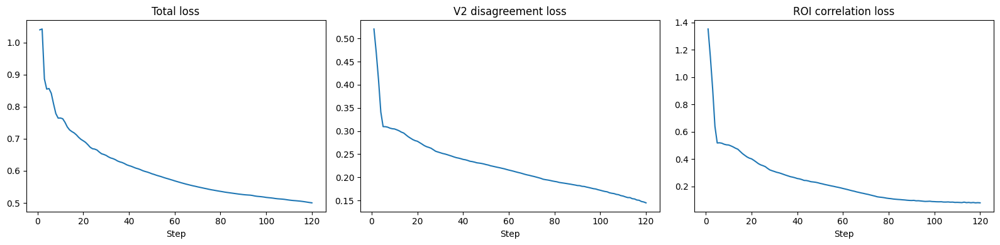


MAD-SEG V2 FOUR-IMAGE OVERFIT GATE PASSED
Fixed IDs: ['ISIC_0000428', 'ISIC_0000024', 'ISIC_0000004', 'ISIC_0010183']
IAA groups: ['low', 'medium', 'high', 'medium']
Annotation counts: [2, 2, 2, 5]

Elapsed: 7.77 seconds
Seconds/step: 0.0648
Peak GPU memory: 1.89 GB
Finite-gradient tensors: 117/117

Loss changes:
total                               : 1.039904 -> 0.499691 (change -0.540213)
segmentation                        : 0.372396 -> 0.165460 (change -0.206936)
soft_consensus                      : 0.372396 -> 0.167162 (change -0.205234)
boundary                            : 0.572421 -> 0.544218 (change -0.028203)
disagreement                        : 0.522287 -> 0.143122 (change -0.379165)
disagreement_balanced_regression    : 0.178311 -> 0.119782 (change -0.058529)
disagreement_correlation            : 1.358810 -> 0.079249 (change -1.279561)
disagreement_global                 : 0.085466 -> 0.070560 (change -0.014906)
annotator                           : 0.305797 -> 0.088480 (

In [ ]:
import sys
import json
import time
import random
import importlib
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from scipy.stats import spearmanr
from torch.utils.data._utils.collate import default_collate
from tqdm.auto import trange

PROJECT_ROOT = Path("/content/drive/MyDrive/MADSeg")
OUTPUT_ROOT = (
    PROJECT_ROOT / "outputs" / "madseg_v2_multitask_overfit"
)
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

INITIALIZATION_CHECKPOINT = (
    PROJECT_ROOT
    / "outputs"
    / "madseg_stage2_initialization"
    / "madseg_stage2_initialization.pt"
)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import madseg_model
import madseg_v2_losses
import madseg_v2_objective

importlib.reload(madseg_model)
importlib.reload(madseg_v2_losses)
importlib.reload(madseg_v2_objective)

from madseg_model import MADSeg
from madseg_v2_losses import disagreement_roi
from madseg_v2_objective import MADSegV2Loss

assert torch.cuda.is_available()
assert "A100" in torch.cuda.get_device_name(0)

SEED = 4203
STEPS = 120
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda")

fixed_ids = [
    "ISIC_0000428",  # low IAA, K=2
    "ISIC_0000024",  # medium IAA, K=2
    "ISIC_0000004",  # high IAA, K=2
    "ISIC_0010183",  # medium IAA, K=5
]

id_to_index = {
    value: index
    for index, value in enumerate(
        audit_dataset.frame["isic_id"].tolist()
    )
}

missing_ids = [
    value for value in fixed_ids
    if value not in id_to_index
]

assert not missing_ids, f"Missing fixed IDs: {missing_ids}"

fixed_samples = [
    audit_dataset[id_to_index[value]]
    for value in fixed_ids
]

cpu_batch = default_collate(fixed_samples)

def move_batch_to_device(batch, device):
    return {
        key: (
            value.to(device, non_blocking=True)
            if torch.is_tensor(value)
            else value
        )
        for key, value in batch.items()
    }

fixed_batch = move_batch_to_device(cpu_batch, device)

checkpoint = torch.load(
    INITIALIZATION_CHECKPOINT,
    map_location="cpu",
    weights_only=False,
)

model = MADSeg(
    in_channels=3,
    base_channels=16,
    number_of_annotators=checkpoint["number_of_annotators"],
    number_of_tools=checkpoint["number_of_tools"],
    number_of_skills=checkpoint["number_of_skills"],
    embedding_dimension=8,
).to(device)

load_result = model.load_state_dict(
    checkpoint["model_state"],
    strict=True,
)

assert not load_result.missing_keys
assert not load_result.unexpected_keys

criterion = MADSegV2Loss(
    lambda_segmentation=1.0,
    lambda_soft_consensus=0.5,
    lambda_boundary=0.3,
    lambda_disagreement=0.3,
    lambda_annotator=0.5,
    lambda_consistency=0.1,
    roi_dilation_radius=8,
    active_threshold=0.05,
    correlation_weight=0.25,
    disagreement_global_weight=0.05,
).to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

def model_forward(model, batch):
    return model(
        image=batch["image"],
        annotator_ids=batch["annotator_ids"],
        tool_ids=batch["tool_ids"],
        skill_ids=batch["skill_ids"],
        return_annotator_logits=True,
    )

tracked_names = [
    "total",
    "segmentation",
    "soft_consensus",
    "boundary",
    "disagreement",
    "disagreement_balanced_regression",
    "disagreement_correlation",
    "disagreement_global",
    "annotator",
    "consistency",
]

def evaluate_losses():
    model.eval()

    with torch.inference_mode():
        outputs = model_forward(model, fixed_batch)
        losses = criterion(outputs, fixed_batch)

    return {
        key: float(losses[key].detach())
        for key in tracked_names
    }

def disagreement_spearman():
    model.eval()

    with torch.inference_mode():
        outputs = model_forward(model, fixed_batch)
        prediction = torch.sigmoid(
            outputs["disagreement_logits"]
        )

        target = fixed_batch["human_disagreement"]

        roi = disagreement_roi(
            fixed_batch["human_masks"],
            fixed_batch["mask_valid"],
            dilation_radius=8,
        ) > 0.5

    correlations = []

    for index in range(target.shape[0]):
        selected = roi[index].flatten()

        predicted_values = (
            prediction[index].flatten()[selected].float().cpu().numpy()
        )

        target_values = (
            target[index].flatten()[selected].float().cpu().numpy()
        )

        if (
            np.std(predicted_values) > 1e-8
            and np.std(target_values) > 1e-8
        ):
            correlation = spearmanr(
                predicted_values,
                target_values,
            ).statistic
        else:
            correlation = np.nan

        correlations.append(float(correlation))

    finite_values = [
        value for value in correlations
        if np.isfinite(value)
    ]

    mean_correlation = (
        float(np.mean(finite_values))
        if finite_values
        else float("nan")
    )

    return mean_correlation, correlations

torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

initial_losses = evaluate_losses()
initial_spearman, initial_case_spearman = (
    disagreement_spearman()
)

history = []
start_time = time.perf_counter()

model.train()

progress = trange(STEPS, desc="MAD-Seg v2 overfit")

for step in progress:
    optimizer.zero_grad(set_to_none=True)

    with torch.autocast(
        device_type="cuda",
        dtype=torch.bfloat16,
    ):
        outputs = model_forward(model, fixed_batch)
        losses = criterion(outputs, fixed_batch)

    assert torch.isfinite(losses["total"])

    losses["total"].backward()

    finite_gradient_tensors = 0
    total_gradient_tensors = 0

    for parameter in model.parameters():
        if parameter.grad is not None:
            total_gradient_tensors += 1

            if torch.isfinite(parameter.grad).all():
                finite_gradient_tensors += 1

    assert finite_gradient_tensors == total_gradient_tensors

    torch.nn.utils.clip_grad_norm_(
        model.parameters(),
        max_norm=5.0,
    )

    optimizer.step()

    record = {
        "step": step + 1,
        **{
            key: float(losses[key].detach())
            for key in tracked_names
        },
    }

    history.append(record)

    progress.set_postfix(
        total=f"{record['total']:.4f}",
        disagreement=f"{record['disagreement']:.4f}",
        correlation=f"{record['disagreement_correlation']:.4f}",
    )

elapsed_seconds = time.perf_counter() - start_time
final_losses = evaluate_losses()
final_spearman, final_case_spearman = (
    disagreement_spearman()
)

peak_memory_gb = (
    torch.cuda.max_memory_allocated() / (1024 ** 3)
)

history_frame = pd.DataFrame(history)
history_path = OUTPUT_ROOT / "history.csv"
history_frame.to_csv(history_path, index=False)

checkpoint_path = OUTPUT_ROOT / "checkpoint.pt"

torch.save(
    {
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "initialization_checkpoint": str(
            INITIALIZATION_CHECKPOINT
        ),
        "steps": STEPS,
        "fixed_ids": fixed_ids,
        "seed": SEED,
        "initial_losses": initial_losses,
        "final_losses": final_losses,
        "initial_mean_roi_spearman": initial_spearman,
        "final_mean_roi_spearman": final_spearman,
        "loss_configuration": {
            "roi_dilation_radius": 8,
            "active_threshold": 0.05,
            "correlation_weight": 0.25,
            "global_weight": 0.05,
            "lambda_disagreement": 0.3,
        },
        "test_set_evaluated": False,
    },
    checkpoint_path,
)

summary = {
    "fixed_ids": fixed_ids,
    "iaa_groups": list(cpu_batch["iaa_group"]),
    "annotation_counts": (
        cpu_batch["num_human_masks"].tolist()
    ),
    "steps": STEPS,
    "elapsed_seconds": elapsed_seconds,
    "seconds_per_step": elapsed_seconds / STEPS,
    "peak_gpu_memory_gb": peak_memory_gb,
    "initial_losses": initial_losses,
    "final_losses": final_losses,
    "initial_mean_roi_spearman": initial_spearman,
    "final_mean_roi_spearman": final_spearman,
    "initial_case_roi_spearman": initial_case_spearman,
    "final_case_roi_spearman": final_case_spearman,
    "finite_gradient_tensors": finite_gradient_tensors,
    "total_gradient_tensors": total_gradient_tensors,
    "test_set_evaluated": False,
}

with open(
    OUTPUT_ROOT / "summary.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(summary, file, indent=2)

figure, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(history_frame["step"], history_frame["total"])
axes[0].set_title("Total loss")
axes[0].set_xlabel("Step")

axes[1].plot(
    history_frame["step"],
    history_frame["disagreement"],
)
axes[1].set_title("V2 disagreement loss")
axes[1].set_xlabel("Step")

axes[2].plot(
    history_frame["step"],
    history_frame["disagreement_correlation"],
)
axes[2].set_title("ROI correlation loss")
axes[2].set_xlabel("Step")

figure.tight_layout()
figure.savefig(
    OUTPUT_ROOT / "loss_curves.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()

assert np.isfinite(final_losses["total"])
assert np.isfinite(final_losses["disagreement"])
assert final_losses["total"] < initial_losses["total"]
assert (
    final_losses["disagreement"]
    < initial_losses["disagreement"]
)
assert finite_gradient_tensors == total_gradient_tensors

print("\nMAD-SEG V2 FOUR-IMAGE OVERFIT GATE PASSED")
print("Fixed IDs:", fixed_ids)
print("IAA groups:", list(cpu_batch["iaa_group"]))
print(
    "Annotation counts:",
    cpu_batch["num_human_masks"].tolist(),
)
print()
print(f"Elapsed: {elapsed_seconds:.2f} seconds")
print(f"Seconds/step: {elapsed_seconds / STEPS:.4f}")
print(f"Peak GPU memory: {peak_memory_gb:.2f} GB")
print(
    "Finite-gradient tensors:",
    f"{finite_gradient_tensors}/{total_gradient_tensors}",
)
print()
print("Loss changes:")

for key in tracked_names:
    change = final_losses[key] - initial_losses[key]

    print(
        f"{key:36s}: "
        f"{initial_losses[key]:.6f} -> "
        f"{final_losses[key]:.6f} "
        f"(change {change:+.6f})"
    )

print()
print(
    "Mean ROI disagreement Spearman:",
    f"{initial_spearman:.6f} -> {final_spearman:.6f}",
)
print("History:", history_path)
print("Checkpoint:", checkpoint_path)
print("Summary:", OUTPUT_ROOT / "summary.json")
print("Test images accessed: 0")
print()
print("Engineering gate passed; full v2 training has not started.")

In [ ]:
from pathlib import Path

import pandas as pd
import torch

V1_RUN = Path(
    "/content/drive/MyDrive/MADSeg/outputs/madseg_stage2_v1"
)

assert V1_RUN.exists(), V1_RUN

print("MAD-SEG V1 TRAINING CONFIGURATION AUDIT")
print("Run directory:", V1_RUN)
print()
print("Available top-level files:")

for path in sorted(V1_RUN.iterdir()):
    if path.is_file():
        print(f"  {path.name}: {path.stat().st_size:,} bytes")

history_path = V1_RUN / "history.csv"
last_checkpoint_path = V1_RUN / "last_checkpoint.pt"
best_checkpoint_path = V1_RUN / "best_checkpoint.pt"

assert history_path.exists(), history_path

# Locate checkpoints if their names differ.
if not last_checkpoint_path.exists():
    candidates = sorted(V1_RUN.glob("*last*.pt"))
    if candidates:
        last_checkpoint_path = candidates[0]

if not best_checkpoint_path.exists():
    candidates = sorted(V1_RUN.glob("*best*.pt"))
    if candidates:
        best_checkpoint_path = candidates[0]

assert last_checkpoint_path.exists(), (
    f"Last checkpoint not found under {V1_RUN}"
)
assert best_checkpoint_path.exists(), (
    f"Best checkpoint not found under {V1_RUN}"
)

history = pd.read_csv(history_path)

print()
print("History columns:")
print(history.columns.tolist())

print()
print("First two history rows:")
display(history.head(2))

print("Last two history rows:")
display(history.tail(2))

checkpoint = torch.load(
    last_checkpoint_path,
    map_location="cpu",
    weights_only=False,
)

print()
print("Last checkpoint:", last_checkpoint_path)
print("Checkpoint keys:")
print(sorted(checkpoint.keys()))

print()
print("Stored scalar/configuration values:")

for key, value in checkpoint.items():
    if isinstance(value, (str, int, float, bool, type(None))):
        print(f"  {key}: {value}")
    elif isinstance(value, dict) and any(
        token in key.lower()
        for token in ["config", "metric", "weight", "loss"]
    ):
        print(f"  {key}: {value}")

optimizer_state = None

for key in [
    "optimizer_state",
    "optimizer_state_dict",
    "optimizer",
]:
    if isinstance(checkpoint.get(key), dict):
        optimizer_state = checkpoint[key]
        print("\nOptimizer state key:", key)
        break

if optimizer_state is not None:
    for index, group in enumerate(
        optimizer_state.get("param_groups", [])
    ):
        settings = {
            key: value
            for key, value in group.items()
            if key != "params"
        }
        print(f"Optimizer group {index}:")
        print(settings)

scheduler_state = None

for key in [
    "scheduler_state",
    "scheduler_state_dict",
    "scheduler",
]:
    if isinstance(checkpoint.get(key), dict):
        scheduler_state = checkpoint[key]
        print("\nScheduler state key:", key)
        print(scheduler_state)
        break

best_checkpoint = torch.load(
    best_checkpoint_path,
    map_location="cpu",
    weights_only=False,
)

print()
print("Best checkpoint:", best_checkpoint_path)
print("Best checkpoint keys:", sorted(best_checkpoint.keys()))

for key, value in best_checkpoint.items():
    if isinstance(value, (str, int, float, bool, type(None))):
        print(f"  {key}: {value}")

print()
print("Configuration audit complete.")
print("No training, validation inference, or test access performed.")

MAD-SEG V1 TRAINING CONFIGURATION AUDIT
Run directory: /content/drive/MyDrive/MADSeg/outputs/madseg_stage2_v1

Available top-level files:
  best_checkpoint.pt: 32,751,504 bytes
  config.json: 999 bytes
  history.csv: 5,018 bytes
  last_checkpoint.pt: 32,755,408 bytes

History columns:
['epoch', 'training_total_loss', 'validation_total_loss', 'validation_segmentation_loss', 'validation_soft_consensus_loss', 'validation_boundary_loss', 'validation_disagreement_loss', 'validation_annotator_loss', 'validation_consistency_loss', 'expected_human_dice', 'consensus_dice', 'staple_dice', 'majority_dice', 'boundary_head_dice', 'disagreement_head_mae', 'annotator_branch_dice', 'pretrained_learning_rate', 'new_branch_learning_rate', 'epoch_seconds', 'improved', 'initialization_only', 'training_segmentation_loss', 'training_soft_consensus_loss', 'training_boundary_loss', 'training_disagreement_loss', 'training_annotator_loss', 'training_consistency_loss']

First two history rows:


,epoch,training_total_loss,validation_total_loss,validation_segmentation_loss,validation_soft_consensus_loss,validation_boundary_loss,validation_disagreement_loss,validation_annotator_loss,validation_consistency_loss,expected_human_dice,...,new_branch_learning_rate,epoch_seconds,improved,initialization_only,training_segmentation_loss,training_soft_consensus_loss,training_boundary_loss,training_disagreement_loss,training_annotator_loss,training_consistency_loss
0,0,NaN,0.534227,0.173617,0.173617,0.570915,0.043999,0.178656,0.00000,0.847626,...,0.001,0.000000,True,True,NaN,NaN,NaN,NaN,NaN,NaN
1,1,0.521667,0.475802,0.167796,0.167815,0.433414,0.040374,0.163907,0.00009,0.847471,...,0.001,89.465344,False,False,0.180844,0.1808,0.49342,0.037275,0.182364,0.000324


Last two history rows:


,epoch,training_total_loss,validation_total_loss,validation_segmentation_loss,validation_soft_consensus_loss,validation_boundary_loss,validation_disagreement_loss,validation_annotator_loss,validation_consistency_loss,expected_human_dice,...,new_branch_learning_rate,epoch_seconds,improved,initialization_only,training_segmentation_loss,training_soft_consensus_loss,training_boundary_loss,training_disagreement_loss,training_annotator_loss,training_consistency_loss
8,8,0.445087,0.446077,0.166871,0.166872,0.359874,0.032287,0.156214,0.000143,0.848564,...,0.0005,84.740650,False,False,0.167505,0.167517,0.343905,0.030163,0.163186,0.000102
9,9,0.442593,0.444287,0.165672,0.165766,0.358239,0.031467,0.157549,0.000457,0.847922,...,0.0005,84.260881,False,False,0.166478,0.166513,0.342450,0.029728,0.162368,0.000208



Last checkpoint: /content/drive/MyDrive/MADSeg/outputs/madseg_stage2_v1/last_checkpoint.pt
Checkpoint keys:
['best_validation_score', 'config', 'cuda_rng_state', 'epoch', 'epochs_without_improvement', 'history', 'loader_generator_state', 'model_state', 'numpy_rng_state', 'optimizer_state', 'python_rng_state', 'scaler_state', 'scheduler_state', 'source_initialization', 'stage', 'torch_rng_state']

Stored scalar/configuration values:
  stage: 2
  epoch: 9
  scaler_state: None
  best_validation_score: 0.8509211579958598
  epochs_without_improvement: 5
  config: {'run_name': 'madseg_stage2_v1', 'stage': 'multi_annotator_finetuning', 'initialization': '/content/drive/MyDrive/MADSeg/outputs/madseg_stage2_initialization/madseg_stage2_initialization.pt', 'training_images': 1675, 'validation_images': 240, 'test_images': 479, 'architecture': 'MAD-Seg', 'parameters': 2714749, 'image_size': 352, 'batch_size': 16, 'maximum_epochs': 30, 'early_stopping_patience': 5, 'optimizer': 'AdamW', 'pretraine

In [ ]:
import torch

print("INITIALIZATION REPRODUCTION DIAGNOSTIC")
print()

print("Stored Stage-2 metrics:")
for key, value in initialization[
    "restored_stage2_validation_metrics"
].items():
    print(f"  {key:30s}: {float(value):.9f}")

print()
print("Currently reproduced metrics:")
for key in [
    "validation_total_loss",
    "validation_segmentation_loss",
    "expected_human_dice",
    "consensus_dice",
    "staple_dice",
    "majority_dice",
]:
    if key in initial_validation:
        print(
            f"  {key:30s}: "
            f"{float(initial_validation[key]):.9f}"
        )

print()
print("Differences for common metrics:")

stored_metrics = initialization[
    "restored_stage2_validation_metrics"
]

for key, stored_value in stored_metrics.items():
    if key in initial_validation:
        reproduced_value = float(initial_validation[key])
        difference = reproduced_value - float(stored_value)

        print(
            f"  {key:30s}: {difference:+.9f}"
        )

print()
print("Initialization source:")
print(initialization["source_checkpoint"])
print("Current dataset module:")
print(sys.modules["multiannotator_data"].__file__)
print()
print("No training or test evaluation performed.")

INITIALIZATION REPRODUCTION DIAGNOSTIC

Stored Stage-2 metrics:
  validation_loss               : 0.173616543
  expected_human_dice           : 0.847625927
  consensus_dice                : 0.852893694
  staple_dice                   : 0.849997811
  majority_dice                 : 0.852893694

Currently reproduced metrics:
  validation_total_loss         : 0.669211328
  validation_segmentation_loss  : 0.173866787
  expected_human_dice           : 0.846196266
  consensus_dice                : 0.862499472
  staple_dice                   : 0.843888994
  majority_dice                 : 0.862499472

Differences for common metrics:
  expected_human_dice           : -0.001429661
  consensus_dice                : +0.009605777
  staple_dice                   : -0.006108816
  majority_dice                 : +0.009605777

Initialization source:
/content/drive/MyDrive/MADSeg/outputs/single_annotator_pretraining_v1/best_checkpoint.pt
Current dataset module:
/content/drive/MyDrive/MADSeg/multiannota

In [ ]:
import sys
import inspect
import importlib
from pathlib import Path

PROJECT_ROOT = Path("/content/drive/MyDrive/MADSeg")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import single_annotator_data
importlib.reload(single_annotator_data)

from single_annotator_data import SingleAnnotatorDataset

print("SINGLE-ANNOTATOR REFERENCE IMPLEMENTATION")
print("Module:", single_annotator_data.__file__)
print()

print("Module-level constants:")
for name, value in vars(single_annotator_data).items():
    if (
        name.isupper()
        and isinstance(
            value,
            (str, int, float, bool, list, tuple, dict),
        )
    ):
        print(f"  {name} = {value}")

print()
print("Dataset methods:")

methods = []

for name, value in vars(SingleAnnotatorDataset).items():
    if inspect.isfunction(value):
        methods.append(name)
        print(" ", name, inspect.signature(value))

print()
print("Relevant method source:")

relevant_tokens = [
    "init",
    "getitem",
    "load",
    "read",
    "image",
    "mask",
    "augment",
    "transform",
    "resize",
    "boundary",
]

printed = set()

for method_name in methods:
    if any(
        token in method_name.lower()
        for token in relevant_tokens
    ):
        method = getattr(
            SingleAnnotatorDataset,
            method_name,
        )

        print("\n" + "=" * 70)
        print(f"METHOD: {method_name}")
        print("=" * 70)
        print(inspect.getsource(method))
        printed.add(method_name)

print()
print("Referenced module helper functions:")

for name, value in vars(single_annotator_data).items():
    if (
        inspect.isfunction(value)
        and value.__module__ == single_annotator_data.__name__
    ):
        print("\n" + "=" * 70)
        print(f"FUNCTION: {name}{inspect.signature(value)}")
        print("=" * 70)
        print(inspect.getsource(value))

print()
print("Source inspection complete.")
print("No training, validation inference, or test access performed.")

SINGLE-ANNOTATOR REFERENCE IMPLEMENTATION
Module: /content/drive/MyDrive/MADSeg/single_annotator_data.py

Module-level constants:

Dataset methods:
  __init__ (self, frame, local_root, annotator_to_id, tool_to_id, skill_to_id, image_size=352, augment=False)
  __len__ (self)
  __getitem__ (self, index)

Relevant method source:

METHOD: __init__
    def __init__(
        self,
        frame,
        local_root,
        annotator_to_id,
        tool_to_id,
        skill_to_id,
        image_size=352,
        augment=False,
    ):
        self.frame = frame.reset_index(drop=True).copy()
        self.local_root = Path(local_root)
        self.annotator_to_id = annotator_to_id
        self.tool_to_id = tool_to_id
        self.skill_to_id = skill_to_id
        self.image_size = image_size
        self.augment = augment

        self.color_jitter = ColorJitter(
            brightness=0.15,
            contrast=0.15,
            saturation=0.10,
            hue=0.02,
        )

        required

In [ ]:
%%writefile /content/drive/MyDrive/MADSeg/multiannotator_data.py

import json
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import torch

from torch.utils.data import Dataset
from torchvision.transforms import ColorJitter
from torchvision.transforms.functional import normalize


def parse_list(value):
    if isinstance(value, list):
        return value

    if isinstance(value, np.ndarray):
        return value.tolist()

    if pd.isna(value):
        return []

    return json.loads(value)


def resolve_image(local_root, row):
    local_root = Path(local_root)
    relative_path = Path(str(row["image_relpath"]))
    candidate = local_root / relative_path

    if candidate.exists():
        return candidate

    image_root = local_root / "images"
    isic_id = str(row["isic_id"])

    for suffix in [
        ".jpg", ".JPG", ".jpeg",
        ".JPEG", ".png", ".PNG",
    ]:
        candidate = image_root / f"{isic_id}{suffix}"

        if candidate.exists():
            return candidate

    raise FileNotFoundError(f"Image not found: {isic_id}")


def resolve_mask(local_root, relative_path):
    local_root = Path(local_root)
    relative_path = Path(str(relative_path))

    candidate = local_root / relative_path

    if candidate.exists():
        return candidate

    candidate = local_root / "segs" / relative_path.name

    if candidate.exists():
        return candidate

    raise FileNotFoundError(
        f"Mask not found: {relative_path}"
    )


def read_rgb(path, image_size):
    image = cv2.imread(
        str(path),
        cv2.IMREAD_COLOR,
    )

    if image is None:
        raise RuntimeError(f"Unreadable image: {path}")

    image = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB,
    )

    return cv2.resize(
        image,
        (image_size, image_size),
        interpolation=cv2.INTER_LINEAR,
    )


def read_binary_mask(path, image_size):
    mask = cv2.imread(
        str(path),
        cv2.IMREAD_GRAYSCALE,
    )

    if mask is None:
        raise RuntimeError(f"Unreadable mask: {path}")

    mask = cv2.resize(
        mask,
        (image_size, image_size),
        interpolation=cv2.INTER_NEAREST,
    )

    # This is the original validated threshold.
    return (mask > 0).astype(np.float32)


def inner_boundary_band(mask, dilation_radius=2):
    binary = (mask > 0.5).astype(np.uint8)

    eroded = cv2.erode(
        binary,
        np.ones((3, 3), dtype=np.uint8),
        iterations=1,
    )

    inner_contour = binary - eroded

    boundary = cv2.dilate(
        inner_contour,
        np.ones(
            (
                2 * dilation_radius + 1,
                2 * dilation_radius + 1,
            ),
            dtype=np.uint8,
        ),
        iterations=1,
    )

    return (boundary > 0).astype(np.float32)


def normalized_binary_entropy(probability, epsilon=1e-7):
    probability = probability.astype(np.float32)

    clipped = np.clip(
        probability,
        epsilon,
        1.0 - epsilon,
    )

    entropy = -(
        clipped * np.log2(clipped)
        + (1.0 - clipped) * np.log2(1.0 - clipped)
    )

    entropy[
        (probability <= 0.0)
        | (probability >= 1.0)
    ] = 0.0

    return entropy.astype(np.float32)


def apply_geometry(
    array,
    horizontal_flip,
    vertical_flip,
    rotations,
):
    if horizontal_flip:
        array = np.flip(array, axis=-1)

    if vertical_flip:
        array = np.flip(array, axis=-2)

    if rotations:
        array = np.rot90(
            array,
            k=rotations,
            axes=(-2, -1),
        )

    return np.ascontiguousarray(array)


class MultiAnnotatorDataset(Dataset):
    def __init__(
        self,
        frame,
        local_root,
        annotator_to_id,
        tool_to_id,
        skill_to_id,
        image_size=352,
        max_annotators=5,
        augment=False,
    ):
        self.frame = frame.reset_index(drop=True).copy()
        self.local_root = Path(local_root)

        self.annotator_to_id = dict(annotator_to_id)
        self.tool_to_id = dict(tool_to_id)
        self.skill_to_id = dict(skill_to_id)

        self.image_size = int(image_size)
        self.max_annotators = int(max_annotators)
        self.augment = bool(augment)

        self.color_jitter = ColorJitter(
            brightness=0.15,
            contrast=0.15,
            saturation=0.10,
            hue=0.02,
        )

        required_columns = {
            "isic_id",
            "split",
            "image_relpath",
            "human_mask_relpaths",
            "annotators",
            "tools",
            "skill_levels",
            "staple_mask_relpath",
            "majority_mask_relpath",
            "iaa_group",
        }

        missing = required_columns - set(self.frame.columns)

        if missing:
            raise ValueError(
                f"Missing index columns: {sorted(missing)}"
            )

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, index):
        row = self.frame.iloc[index]

        human_relpaths = parse_list(
            row["human_mask_relpaths"]
        )
        annotators = parse_list(row["annotators"])
        tools = parse_list(row["tools"])
        skill_levels = parse_list(
            row["skill_levels"]
        )

        number_of_masks = len(human_relpaths)

        assert 1 <= number_of_masks <= self.max_annotators
        assert len(annotators) == number_of_masks
        assert len(tools) == number_of_masks
        assert len(skill_levels) == number_of_masks

        image = read_rgb(
            resolve_image(self.local_root, row),
            self.image_size,
        )

        human_masks = [
            read_binary_mask(
                resolve_mask(self.local_root, relative_path),
                self.image_size,
            )
            for relative_path in human_relpaths
        ]

        staple_mask = read_binary_mask(
            resolve_mask(
                self.local_root,
                row["staple_mask_relpath"],
            ),
            self.image_size,
        )

        majority_mask = read_binary_mask(
            resolve_mask(
                self.local_root,
                row["majority_mask_relpath"],
            ),
            self.image_size,
        )

        horizontal_flip = False
        vertical_flip = False
        rotations = 0

        if self.augment:
            horizontal_flip = bool(
                torch.rand(()) < 0.5
            )
            vertical_flip = bool(
                torch.rand(()) < 0.5
            )
            rotations = int(
                torch.randint(0, 4, (1,)).item()
            )

        image = np.moveaxis(image, -1, 0)

        image = apply_geometry(
            image,
            horizontal_flip,
            vertical_flip,
            rotations,
        )

        human_masks = [
            apply_geometry(
                mask[None],
                horizontal_flip,
                vertical_flip,
                rotations,
            )[0]
            for mask in human_masks
        ]

        staple_mask = apply_geometry(
            staple_mask[None],
            horizontal_flip,
            vertical_flip,
            rotations,
        )[0]

        majority_mask = apply_geometry(
            majority_mask[None],
            horizontal_flip,
            vertical_flip,
            rotations,
        )[0]

        human_stack = np.stack(
            human_masks,
            axis=0,
        ).astype(np.float32)

        soft_consensus = human_stack.mean(
            axis=0,
            keepdims=True,
        ).astype(np.float32)

        hard_consensus = (
            soft_consensus >= 0.5
        ).astype(np.float32)

        human_disagreement = (
            normalized_binary_entropy(
                soft_consensus
            )
        )

        boundaries = []
        individual_boundary_validity = []

        for mask in human_stack:
            foreground = float(mask.sum())
            total_pixels = float(mask.size)

            boundary_is_valid = (
                foreground > 0.0
                and foreground < total_pixels
            )

            individual_boundary_validity.append(
                boundary_is_valid
            )

            if boundary_is_valid:
                boundaries.append(
                    inner_boundary_band(mask)
                )
            else:
                boundaries.append(
                    np.zeros_like(mask, dtype=np.float32)
                )

        human_boundaries = np.stack(
            boundaries,
            axis=0,
        ).astype(np.float32)

        valid_boundary_array = np.asarray(
            individual_boundary_validity,
            dtype=bool,
        )

        if valid_boundary_array.any():
            boundary_probability = (
                human_boundaries[
                    valid_boundary_array
                ].mean(
                    axis=0,
                    keepdims=True,
                )
            ).astype(np.float32)
        else:
            boundary_probability = np.zeros_like(
                soft_consensus,
                dtype=np.float32,
            )

        boundary_disagreement = (
            normalized_binary_entropy(
                boundary_probability
            )
        )

        consensus_foreground = float(
            hard_consensus.sum()
        )

        consensus_valid = (
            consensus_foreground > 0.0
            and consensus_foreground
            < hard_consensus.size
        )

        if consensus_valid:
            consensus_boundary = (
                inner_boundary_band(
                    hard_consensus[0]
                )[None]
            )
        else:
            consensus_boundary = np.zeros_like(
                hard_consensus,
                dtype=np.float32,
            )

        padded_masks = np.zeros(
            (
                self.max_annotators,
                self.image_size,
                self.image_size,
            ),
            dtype=np.float32,
        )

        padded_boundaries = np.zeros_like(
            padded_masks
        )

        mask_valid = np.zeros(
            self.max_annotators,
            dtype=bool,
        )

        boundary_valid = np.zeros(
            self.max_annotators,
            dtype=bool,
        )

        annotator_ids = np.full(
            self.max_annotators,
            -1,
            dtype=np.int64,
        )

        tool_ids = np.full(
            self.max_annotators,
            -1,
            dtype=np.int64,
        )

        skill_ids = np.full(
            self.max_annotators,
            -1,
            dtype=np.int64,
        )

        padded_masks[:number_of_masks] = human_stack
        padded_boundaries[:number_of_masks] = (
            human_boundaries
        )
        mask_valid[:number_of_masks] = True
        boundary_valid[:number_of_masks] = (
            valid_boundary_array
        )

        for position in range(number_of_masks):
            annotator_ids[position] = (
                self.annotator_to_id[
                    annotators[position]
                ]
            )
            tool_ids[position] = self.tool_to_id[
                tools[position]
            ]
            skill_ids[position] = self.skill_to_id[
                skill_levels[position]
            ]

        image = (
            torch.from_numpy(image)
            .float()
            .div_(255.0)
        )

        if self.augment:
            image = self.color_jitter(image)

        image = normalize(
            image,
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225],
        )

        iaa_group = str(row["iaa_group"])
        iaa_to_id = {
            "low": 0,
            "medium": 1,
            "high": 2,
        }

        return {
            "image": image,
            "human_masks": torch.from_numpy(
                padded_masks
            ).float(),
            "mask_valid": torch.from_numpy(
                mask_valid
            ).bool(),
            "human_boundaries": torch.from_numpy(
                padded_boundaries
            ).float(),
            "boundary_valid": torch.from_numpy(
                boundary_valid
            ).bool(),
            "annotator_ids": torch.from_numpy(
                annotator_ids
            ).long(),
            "tool_ids": torch.from_numpy(
                tool_ids
            ).long(),
            "skill_ids": torch.from_numpy(
                skill_ids
            ).long(),
            "soft_consensus": torch.from_numpy(
                soft_consensus
            ).float(),
            "human_disagreement": torch.from_numpy(
                human_disagreement
            ).float(),
            "hard_consensus": torch.from_numpy(
                hard_consensus
            ).float(),
            "consensus_boundary": torch.from_numpy(
                consensus_boundary
            ).float(),
            "boundary_probability": torch.from_numpy(
                boundary_probability
            ).float(),
            "boundary_disagreement": torch.from_numpy(
                boundary_disagreement
            ).float(),
            "staple_mask": torch.from_numpy(
                staple_mask[None]
            ).float(),
            "majority_mask": torch.from_numpy(
                majority_mask[None]
            ).float(),
            "num_human_masks": torch.tensor(
                number_of_masks,
                dtype=torch.long,
            ),
            "iaa_id": torch.tensor(
                iaa_to_id[iaa_group],
                dtype=torch.long,
            ),
            "isic_id": str(row["isic_id"]),
            "split": str(row["split"]),
            "iaa_group": iaa_group,
        }

Overwriting /content/drive/MyDrive/MADSeg/multiannotator_data.py


In [ ]:
import sys
import random
import importlib

import numpy as np
import torch

from torch.utils.data import DataLoader

import multiannotator_data
importlib.reload(multiannotator_data)

from multiannotator_data import MultiAnnotatorDataset

train_dataset = MultiAnnotatorDataset(
    frame=train_frame,
    local_root=LOCAL_ROOT,
    annotator_to_id=ANNOTATOR_TO_ID,
    tool_to_id=TOOL_TO_ID,
    skill_to_id=SKILL_TO_ID,
    image_size=352,
    augment=True,
)

validation_dataset = MultiAnnotatorDataset(
    frame=validation_frame,
    local_root=LOCAL_ROOT,
    annotator_to_id=ANNOTATOR_TO_ID,
    tool_to_id=TOOL_TO_ID,
    skill_to_id=SKILL_TO_ID,
    image_size=352,
    augment=False,
)

test_dataset = MultiAnnotatorDataset(
    frame=test_frame,
    local_root=LOCAL_ROOT,
    annotator_to_id=ANNOTATOR_TO_ID,
    tool_to_id=TOOL_TO_ID,
    skill_to_id=SKILL_TO_ID,
    image_size=352,
    augment=False,
)

v2_loader_generator = torch.Generator()
v2_loader_generator.manual_seed(442)

def v2_seed_worker(worker_id):
    worker_seed = torch.initial_seed() % (2**32)
    np.random.seed(worker_seed)
    random.seed(worker_seed)

loader_options = {
    "batch_size": 16,
    "num_workers": 8,
    "pin_memory": True,
    "persistent_workers": True,
    "prefetch_factor": 2,
    "worker_init_fn": v2_seed_worker,
}

v2_train_loader = DataLoader(
    train_dataset,
    shuffle=True,
    drop_last=True,
    generator=v2_loader_generator,
    **loader_options,
)

v2_validation_loader = DataLoader(
    validation_dataset,
    shuffle=False,
    drop_last=False,
    **loader_options,
)

# Restore the clean initialization again.
model.load_state_dict(
    initialization["model_state"],
    strict=True,
)

initial_validation = validate()

stored = initialization[
    "restored_stage2_validation_metrics"
]

comparisons = {
    "validation_loss": (
        initial_validation[
            "validation_segmentation_loss"
        ],
        float(stored["validation_loss"]),
    ),
    "expected_human_dice": (
        initial_validation["expected_human_dice"],
        float(stored["expected_human_dice"]),
    ),
    "consensus_dice": (
        initial_validation["consensus_dice"],
        float(stored["consensus_dice"]),
    ),
    "staple_dice": (
        initial_validation["staple_dice"],
        float(stored["staple_dice"]),
    ),
    "majority_dice": (
        initial_validation["majority_dice"],
        float(stored["majority_dice"]),
    ),
}

print("EXACT PREPROCESSING RESTORATION CHECK")
print()

maximum_difference = 0.0

for name, (reproduced, expected) in comparisons.items():
    difference = float(reproduced) - expected
    maximum_difference = max(
        maximum_difference,
        abs(difference),
    )

    print(
        f"{name:28s}: "
        f"stored={expected:.9f}  "
        f"restored={float(reproduced):.9f}  "
        f"difference={difference:+.9f}"
    )

print()
print(
    "Maximum absolute difference:",
    f"{maximum_difference:.10f}",
)

assert maximum_difference <  5e-5, (
    "The historical pipeline has not yet been "
    "reproduced exactly."
)

print("Historical Stage-2 initialization reproduced exactly.")
print("Training samples/batches:", len(train_dataset), len(v2_train_loader))
print(
    "Validation samples/batches:",
    len(validation_dataset),
    len(v2_validation_loader),
)
print("Test images accessed: 0")
print("Safe to start full MAD-Seg v2 training.")

Validation:   0%|          | 0/15 [00:00<?, ?it/s]

EXACT PREPROCESSING RESTORATION CHECK

validation_loss             : stored=0.173616543  restored=0.173616321  difference=-0.000000222
expected_human_dice         : stored=0.847625927  restored=0.847614936  difference=-0.000010991
consensus_dice              : stored=0.852893694  restored=0.852879842  difference=-0.000013852
staple_dice                 : stored=0.849997811  restored=0.849989124  difference=-0.000008686
majority_dice               : stored=0.852893694  restored=0.852879842  difference=-0.000013852

Maximum absolute difference: 0.0000138521
Historical Stage-2 initialization reproduced exactly.
Training samples/batches: 1675 104
Validation samples/batches: 240 15
Test images accessed: 0
Safe to start full MAD-Seg v2 training.


Checking clean Stage-2 initialization...


Validation:   0%|          | 0/15 [00:00<?, ?it/s]

Clean initialization validated
Expected-human Dice: 0.847615
Initialization difference: 0.0000110640


Training:   0%|          | 0/104 [00:00<?, ?it/s]

/tmp/ipykernel_1126/1007843787.py:417: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  total=f"{float(losses['total']):.4f}",


...

Validation:   0%|          | 0/15 [00:00<?, ?it/s]

Epoch 18/30 | train=0.490914 | val=0.493171 | human Dice=0.850175 | disagreement=0.209551 | boundary=0.495178 | patience=4/5 | 95.8s


Training:   0%|          | 0/104 [00:00<?, ?it/s]

Validation:   0%|          | 0/15 [00:00<?, ?it/s]

Epoch 19/30 | train=0.488666 | val=0.492518 | human Dice=0.850797 | disagreement=0.210846 | boundary=0.495282 | patience=5/5 | 94.3s

Early stopping at epoch 19: no validation improvement for 5 epochs.


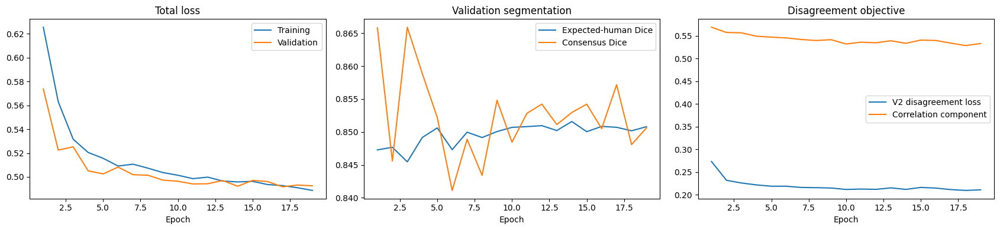


FULL MAD-SEG V2 TRAINING FINISHED
Run: madseg_stage2_v2_roi_balanced_v1
Epochs completed: 19
Best epoch: 14
Best validation expected-human Dice: 0.851581
Best validation disagreement loss: 0.211846
Best validation boundary-head Dice: 0.503171
Elapsed this execution: 30.11 minutes
Best checkpoint: /content/drive/MyDrive/MADSeg/outputs/madseg_stage2_v2_roi_balanced_v1/best_checkpoint.pt
Latest checkpoint: /content/drive/MyDrive/MADSeg/outputs/madseg_stage2_v2_roi_balanced_v1/last_checkpoint.pt
History: /content/drive/MyDrive/MADSeg/outputs/madseg_stage2_v2_roi_balanced_v1/history.csv
Test set has not been evaluated.


In [ ]:
import os
import sys
import json
import time
import random
import importlib
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader
from tqdm.auto import tqdm

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

PROJECT_ROOT = Path("/content/drive/MyDrive/MADSeg")

RUN_ROOT = (
    PROJECT_ROOT
    / "outputs"
    / "madseg_stage2_v2_roi_balanced_v1"
)
RUN_ROOT.mkdir(parents=True, exist_ok=True)

INITIALIZATION_CHECKPOINT = (
    PROJECT_ROOT
    / "outputs"
    / "madseg_stage2_initialization"
    / "madseg_stage2_initialization.pt"
)

BEST_CHECKPOINT = RUN_ROOT / "best_checkpoint.pt"
LAST_CHECKPOINT = RUN_ROOT / "last_checkpoint.pt"
HISTORY_CSV = RUN_ROOT / "history.csv"
CONFIG_JSON = RUN_ROOT / "config.json"
CURVE_PATH = RUN_ROOT / "training_curves.png"

SEED = 442
MAXIMUM_EPOCHS = 30
EARLY_STOPPING_PATIENCE = 5

PRETRAINED_LEARNING_RATE = 2e-4
NEW_BRANCH_LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
GRADIENT_CLIP_NORM = 1.0

BATCH_SIZE = 16
NUM_WORKERS = 8

assert torch.cuda.is_available()
assert "A100" in torch.cuda.get_device_name(0)
assert INITIALIZATION_CHECKPOINT.exists()

device = torch.device("cuda")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import madseg_model
import madseg_v2_losses
import madseg_v2_objective

importlib.reload(madseg_model)
importlib.reload(madseg_v2_losses)
importlib.reload(madseg_v2_objective)

from madseg_model import MADSeg
from madseg_v2_objective import MADSegV2Loss

# ------------------------------------------------------------
# Rebuild loaders with the original Stage-2 seed
# ------------------------------------------------------------

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

v2_loader_generator = torch.Generator()
v2_loader_generator.manual_seed(SEED)

def v2_seed_worker(worker_id):
    worker_seed = torch.initial_seed() % (2**32)
    np.random.seed(worker_seed)
    random.seed(worker_seed)

common_loader_options = {
    "batch_size": BATCH_SIZE,
    "num_workers": NUM_WORKERS,
    "pin_memory": True,
    "persistent_workers": True,
    "prefetch_factor": 2,
    "worker_init_fn": v2_seed_worker,
}

v2_train_loader = DataLoader(
    train_dataset,
    shuffle=True,
    drop_last=True,
    generator=v2_loader_generator,
    **common_loader_options,
)

v2_validation_loader = DataLoader(
    validation_dataset,
    shuffle=False,
    drop_last=False,
    **common_loader_options,
)

assert len(v2_train_loader) == 104
assert len(v2_validation_loader) == 15

# test_loader is deliberately never iterated.

# ------------------------------------------------------------
# Model and clean initialization
# ------------------------------------------------------------

initialization = torch.load(
    INITIALIZATION_CHECKPOINT,
    map_location="cpu",
    weights_only=False,
)

model = MADSeg(
    in_channels=3,
    base_channels=16,
    number_of_annotators=initialization[
        "number_of_annotators"
    ],
    number_of_tools=initialization["number_of_tools"],
    number_of_skills=initialization["number_of_skills"],
    embedding_dimension=8,
).to(device)

load_result = model.load_state_dict(
    initialization["model_state"],
    strict=True,
)

assert not load_result.missing_keys
assert not load_result.unexpected_keys
assert sum(p.numel() for p in model.parameters()) == 2_714_749

# Same differential-learning-rate grouping used by v1.
pretrained_prefixes = (
    "encoder.",
    "shared_encoder.",
    "consensus_decoder.",
    "consensus_head.",
    "raw_consensus_head.",
)

pretrained_parameters = []
new_branch_parameters = []
pretrained_names = []
new_branch_names = []

for name, parameter in model.named_parameters():
    if name.startswith(pretrained_prefixes):
        pretrained_parameters.append(parameter)
        pretrained_names.append(name)
    else:
        new_branch_parameters.append(parameter)
        new_branch_names.append(name)

assert pretrained_parameters
assert new_branch_parameters

grouped_parameter_ids = {
    id(parameter)
    for parameter in (
        pretrained_parameters + new_branch_parameters
    )
}

trainable_parameter_ids = {
    id(parameter)
    for parameter in model.parameters()
    if parameter.requires_grad
}

assert grouped_parameter_ids == trainable_parameter_ids

criterion = MADSegV2Loss(
    lambda_segmentation=1.0,
    lambda_soft_consensus=0.5,
    lambda_boundary=0.3,
    lambda_disagreement=0.3,
    lambda_annotator=0.5,
    lambda_consistency=0.1,
    roi_dilation_radius=8,
    active_threshold=0.05,
    correlation_weight=0.25,
    disagreement_global_weight=0.05,
).to(device)

optimizer = torch.optim.AdamW(
    [
        {
            "params": pretrained_parameters,
            "lr": PRETRAINED_LEARNING_RATE,
            "name": "pretrained",
        },
        {
            "params": new_branch_parameters,
            "lr": NEW_BRANCH_LEARNING_RATE,
            "name": "new_branches",
        },
    ],
    weight_decay=WEIGHT_DECAY,
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2,
    threshold=1e-4,
    threshold_mode="rel",
    cooldown=0,
    min_lr=1e-6,
    eps=1e-8,
)

configuration = {
    "run_name": RUN_ROOT.name,
    "stage": "multi_annotator_finetuning",
    "version": "v2_roi_balanced_disagreement",
    "initialization": str(INITIALIZATION_CHECKPOINT),
    "overfit_checkpoint_used_for_training": False,
    "training_images": len(train_dataset),
    "validation_images": len(validation_dataset),
    "test_images": len(test_dataset),
    "architecture": "MAD-Seg",
    "parameters": sum(p.numel() for p in model.parameters()),
    "image_size": 352,
    "batch_size": BATCH_SIZE,
    "maximum_epochs": MAXIMUM_EPOCHS,
    "early_stopping_patience": EARLY_STOPPING_PATIENCE,
    "optimizer": "AdamW",
    "pretrained_learning_rate": PRETRAINED_LEARNING_RATE,
    "new_branch_learning_rate": NEW_BRANCH_LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "gradient_clip_norm": GRADIENT_CLIP_NORM,
    "scheduler": "ReduceLROnPlateau",
    "scheduler_factor": 0.5,
    "scheduler_patience": 2,
    "scheduler_min_lr": 1e-6,
    "checkpoint_selection": "validation_expected_human_dice",
    "loss_weights": criterion.weights,
    "disagreement_objective": {
        "roi": "human-mask union dilated by 8 pixels",
        "active_threshold": 0.05,
        "correlation_weight": 0.25,
        "global_weight": 0.05,
    },
    "amp_dtype": "torch.bfloat16",
    "device": torch.cuda.get_device_name(0),
    "seed": SEED,
    "test_evaluated": False,
}

with open(CONFIG_JSON, "w", encoding="utf-8") as file:
    json.dump(configuration, file, indent=2)

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------

LOSS_NAMES = [
    "total",
    "segmentation",
    "soft_consensus",
    "boundary",
    "disagreement",
    "disagreement_balanced_regression",
    "disagreement_correlation",
    "disagreement_global",
    "annotator",
    "consistency",
]

def move_to_device(batch):
    return {
        key: (
            value.to(device, non_blocking=True)
            if torch.is_tensor(value)
            else value
        )
        for key, value in batch.items()
    }

def forward_model(batch):
    return model(
        image=batch["image"],
        annotator_ids=batch["annotator_ids"],
        tool_ids=batch["tool_ids"],
        skill_ids=batch["skill_ids"],
        return_annotator_logits=True,
    )

def dice_per_map(prediction, target, epsilon=1e-6):
    prediction = prediction.float()
    target = target.float()

    intersection = (
        prediction * target
    ).sum(dim=(-2, -1))

    denominator = (
        prediction.sum(dim=(-2, -1))
        + target.sum(dim=(-2, -1))
    )

    return (
        2.0 * intersection + epsilon
    ) / (
        denominator + epsilon
    )

def atomic_torch_save(payload, destination):
    temporary = destination.with_suffix(
        destination.suffix + ".temporary"
    )

    torch.save(payload, temporary)
    os.replace(temporary, destination)

def checkpoint_payload(
    epoch,
    history,
    best_score,
    epochs_without_improvement,
):
    return {
        "stage": 2,
        "version": "v2_roi_balanced_disagreement",
        "epoch": epoch,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "scheduler_state": scheduler.state_dict(),
        "scaler_state": None,
        "best_validation_score": best_score,
        "epochs_without_improvement": (
            epochs_without_improvement
        ),
        "history": history,
        "config": configuration,
        "source_initialization": str(
            INITIALIZATION_CHECKPOINT
        ),
        "python_rng_state": random.getstate(),
        "numpy_rng_state": np.random.get_state(),
        "torch_rng_state": torch.get_rng_state(),
        "cuda_rng_state": torch.cuda.get_rng_state_all(),
        "loader_generator_state": (
            v2_loader_generator.get_state()
        ),
        "test_set_evaluated": False,
    }

def train_one_epoch():
    model.train()

    accumulated = {
        name: 0.0 for name in LOSS_NAMES
    }

    images_processed = 0

    progress = tqdm(
        v2_train_loader,
        desc="Training",
        leave=False,
    )

    for batch in progress:
        batch = move_to_device(batch)
        current_batch_size = batch["image"].shape[0]

        optimizer.zero_grad(set_to_none=True)

        with torch.autocast(
            device_type="cuda",
            dtype=torch.bfloat16,
        ):
            outputs = forward_model(batch)
            losses = criterion(outputs, batch)

        assert torch.isfinite(losses["total"])

        losses["total"].backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=GRADIENT_CLIP_NORM,
        )

        optimizer.step()

        for name in LOSS_NAMES:
            accumulated[name] += (
                float(losses[name].detach())
                * current_batch_size
            )

        images_processed += current_batch_size

        progress.set_postfix(
            total=f"{float(losses['total']):.4f}",
            disagreement=(
                f"{float(losses['disagreement']):.4f}"
            ),
        )

    return {
        name: value / images_processed
        for name, value in accumulated.items()
    }

@torch.inference_mode()
def validate():
    model.eval()

    accumulated_losses = {
        name: 0.0 for name in LOSS_NAMES
    }

    images_processed = 0

    metric_sums = {
        "expected_human_dice": 0.0,
        "consensus_dice": 0.0,
        "staple_dice": 0.0,
        "majority_dice": 0.0,
        "boundary_head_dice": 0.0,
        "disagreement_head_mae": 0.0,
        "annotator_branch_dice": 0.0,
    }

    progress = tqdm(
        v2_validation_loader,
        desc="Validation",
        leave=False,
    )

    for batch in progress:
        batch = move_to_device(batch)
        current_batch_size = batch["image"].shape[0]

        with torch.autocast(
            device_type="cuda",
            dtype=torch.bfloat16,
        ):
            outputs = forward_model(batch)
            losses = criterion(outputs, batch)

        for name in LOSS_NAMES:
            accumulated_losses[name] += (
                float(losses[name])
                * current_batch_size
            )

        final_prediction = (
            torch.sigmoid(
                outputs["final_mask_logits"].float()
            ) >= 0.5
        ).float()

        repeated_prediction = final_prediction.expand(
            -1,
            batch["human_masks"].shape[1],
            -1,
            -1,
        )

        human_dice = dice_per_map(
            repeated_prediction,
            batch["human_masks"],
        )

        valid_masks = batch["mask_valid"].float()

        expected_human_dice = (
            (human_dice * valid_masks).sum(dim=1)
            / valid_masks.sum(dim=1).clamp_min(1.0)
        )

        consensus_dice = dice_per_map(
            final_prediction,
            batch["hard_consensus"],
        ).squeeze(1)

        staple_dice = dice_per_map(
            final_prediction,
            batch["staple_mask"],
        ).squeeze(1)

        majority_dice = dice_per_map(
            final_prediction,
            batch["majority_mask"],
        ).squeeze(1)

        boundary_prediction = (
            torch.sigmoid(
                outputs["boundary_logits"].float()
            ) >= 0.5
        ).float()

        boundary_target = (
            batch["boundary_probability"] >= 0.5
        ).float()

        boundary_head_dice = dice_per_map(
            boundary_prediction,
            boundary_target,
        ).squeeze(1)

        disagreement_probability = torch.sigmoid(
            outputs["disagreement_logits"].float()
        )

        disagreement_mae = (
            disagreement_probability
            - batch["human_disagreement"]
        ).abs().flatten(1).mean(dim=1)

        annotator_prediction = (
            torch.sigmoid(
                outputs["annotator_logits"].float()
            ) >= 0.5
        ).float()

        annotator_dice = dice_per_map(
            annotator_prediction,
            batch["human_masks"],
        )

        expected_annotator_dice = (
            (annotator_dice * valid_masks).sum(dim=1)
            / valid_masks.sum(dim=1).clamp_min(1.0)
        )

        metric_sums["expected_human_dice"] += float(
            expected_human_dice.sum()
        )
        metric_sums["consensus_dice"] += float(
            consensus_dice.sum()
        )
        metric_sums["staple_dice"] += float(
            staple_dice.sum()
        )
        metric_sums["majority_dice"] += float(
            majority_dice.sum()
        )
        metric_sums["boundary_head_dice"] += float(
            boundary_head_dice.sum()
        )
        metric_sums["disagreement_head_mae"] += float(
            disagreement_mae.sum()
        )
        metric_sums["annotator_branch_dice"] += float(
            expected_annotator_dice.sum()
        )

        images_processed += current_batch_size

    result = {
        f"validation_{name}_loss": (
            value / images_processed
        )
        for name, value in accumulated_losses.items()
    }

    result.update({
        name: value / images_processed
        for name, value in metric_sums.items()
    })

    return result

# ------------------------------------------------------------
# Resume or initialize
# ------------------------------------------------------------

history = []
best_validation_score = -float("inf")
epochs_without_improvement = 0
start_epoch = 1
resumed = False

if LAST_CHECKPOINT.exists():
    resume_checkpoint = torch.load(
        LAST_CHECKPOINT,
        map_location="cpu",
        weights_only=False,
    )

    assert (
        resume_checkpoint.get("version")
        == "v2_roi_balanced_disagreement"
    )

    model.load_state_dict(
        resume_checkpoint["model_state"],
        strict=True,
    )
    optimizer.load_state_dict(
        resume_checkpoint["optimizer_state"]
    )
    scheduler.load_state_dict(
        resume_checkpoint["scheduler_state"]
    )

    history = resume_checkpoint["history"]
    best_validation_score = resume_checkpoint[
        "best_validation_score"
    ]
    epochs_without_improvement = resume_checkpoint[
        "epochs_without_improvement"
    ]
    start_epoch = int(resume_checkpoint["epoch"]) + 1

    random.setstate(
        resume_checkpoint["python_rng_state"]
    )
    np.random.set_state(
        resume_checkpoint["numpy_rng_state"]
    )
    torch.set_rng_state(
        resume_checkpoint["torch_rng_state"]
    )
    torch.cuda.set_rng_state_all(
        resume_checkpoint["cuda_rng_state"]
    )
    v2_loader_generator.set_state(
        resume_checkpoint["loader_generator_state"]
    )

    resumed = True

    print("Resuming MAD-Seg v2 training")
    print("Completed epoch:", start_epoch - 1)
    print(
        "Best validation Dice:",
        f"{best_validation_score:.6f}",
    )
    print(
        "Epochs without improvement:",
        epochs_without_improvement,
    )

else:
    print("Checking clean Stage-2 initialization...")

    initial_validation = validate()

    expected_initial_score = float(
        initialization[
            "source_validation_expected_human_dice"
        ]
    )

    initialization_difference = abs(
        initial_validation["expected_human_dice"]
        - expected_initial_score
    )

    assert initialization_difference <  5e-5, (
        "Initialization validation mismatch: "
        f"{initialization_difference}"
    )

    best_validation_score = initial_validation[
        "expected_human_dice"
    ]

    initialization_record = {
        "epoch": 0,
        "training_total_loss": np.nan,
        **initial_validation,
        "pretrained_learning_rate": (
            PRETRAINED_LEARNING_RATE
        ),
        "new_branch_learning_rate": (
            NEW_BRANCH_LEARNING_RATE
        ),
        "epoch_seconds": 0.0,
        "improved": True,
        "initialization_only": True,
    }

    history.append(initialization_record)

    initial_payload = checkpoint_payload(
        epoch=0,
        history=history,
        best_score=best_validation_score,
        epochs_without_improvement=0,
    )

    atomic_torch_save(
        initial_payload,
        BEST_CHECKPOINT,
    )
    atomic_torch_save(
        initial_payload,
        LAST_CHECKPOINT,
    )

    pd.DataFrame(history).to_csv(
        HISTORY_CSV,
        index=False,
    )

    print("Clean initialization validated")
    print(
        "Expected-human Dice:",
        f"{best_validation_score:.6f}",
    )
    print(
        "Initialization difference:",
        f"{initialization_difference:.10f}",
    )

# ------------------------------------------------------------
# Full training
# ------------------------------------------------------------

training_start = time.perf_counter()

if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
    print(
        "Training is already early-stopped in the saved checkpoint."
    )

elif start_epoch > MAXIMUM_EPOCHS:
    print("Maximum epoch was already completed.")

else:
    for epoch in range(
        start_epoch,
        MAXIMUM_EPOCHS + 1,
    ):
        epoch_start = time.perf_counter()

        training_metrics = train_one_epoch()
        validation_metrics = validate()

        validation_score = validation_metrics[
            "expected_human_dice"
        ]

        scheduler.step(validation_score)

        improved = (
            validation_score > best_validation_score
        )

        if improved:
            best_validation_score = validation_score
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        epoch_seconds = time.perf_counter() - epoch_start

        record = {
            "epoch": epoch,
            **{
                f"training_{name}_loss": value
                for name, value in training_metrics.items()
            },
            **validation_metrics,
            "pretrained_learning_rate": (
                optimizer.param_groups[0]["lr"]
            ),
            "new_branch_learning_rate": (
                optimizer.param_groups[1]["lr"]
            ),
            "epoch_seconds": epoch_seconds,
            "improved": improved,
            "initialization_only": False,
        }

        history.append(record)

        payload = checkpoint_payload(
            epoch=epoch,
            history=history,
            best_score=best_validation_score,
            epochs_without_improvement=(
                epochs_without_improvement
            ),
        )

        # Save every epoch for safe runtime reconnection.
        atomic_torch_save(payload, LAST_CHECKPOINT)

        if improved:
            atomic_torch_save(
                payload,
                BEST_CHECKPOINT,
            )

        pd.DataFrame(history).to_csv(
            HISTORY_CSV,
            index=False,
        )

        print(
            f"Epoch {epoch:02d}/{MAXIMUM_EPOCHS} | "
            f"train={training_metrics['total']:.6f} | "
            f"val={validation_metrics['validation_total_loss']:.6f} | "
            f"human Dice={validation_score:.6f} | "
            f"disagreement={validation_metrics['validation_disagreement_loss']:.6f} | "
            f"boundary={validation_metrics['boundary_head_dice']:.6f} | "
            f"patience={epochs_without_improvement}/"
            f"{EARLY_STOPPING_PATIENCE} | "
            f"{epoch_seconds:.1f}s"
        )

        if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
            print(
                f"\nEarly stopping at epoch {epoch}: "
                f"no validation improvement for "
                f"{EARLY_STOPPING_PATIENCE} epochs."
            )
            break

total_training_seconds = (
    time.perf_counter() - training_start
)

# ------------------------------------------------------------
# Final records and curves
# ------------------------------------------------------------

history_frame = pd.DataFrame(history)
history_frame.to_csv(HISTORY_CSV, index=False)

trained_history = history_frame[
    history_frame["epoch"] > 0
].copy()

best_row = history_frame.loc[
    history_frame["expected_human_dice"].idxmax()
]

if len(trained_history):
    figure, axes = plt.subplots(1, 3, figsize=(17, 4))

    axes[0].plot(
        trained_history["epoch"],
        trained_history["training_total_loss"],
        label="Training",
    )
    axes[0].plot(
        trained_history["epoch"],
        trained_history["validation_total_loss"],
        label="Validation",
    )
    axes[0].set_title("Total loss")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()

    axes[1].plot(
        trained_history["epoch"],
        trained_history["expected_human_dice"],
        label="Expected-human Dice",
    )
    axes[1].plot(
        trained_history["epoch"],
        trained_history["consensus_dice"],
        label="Consensus Dice",
    )
    axes[1].set_title("Validation segmentation")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()

    axes[2].plot(
        trained_history["epoch"],
        trained_history[
            "validation_disagreement_loss"
        ],
        label="V2 disagreement loss",
    )
    axes[2].plot(
        trained_history["epoch"],
        trained_history[
            "validation_disagreement_correlation_loss"
        ],
        label="Correlation component",
    )
    axes[2].set_title("Disagreement objective")
    axes[2].set_xlabel("Epoch")
    axes[2].legend()

    figure.tight_layout()
    figure.savefig(
        CURVE_PATH,
        dpi=180,
        bbox_inches="tight",
    )
    plt.show()

completion_summary = {
    "run_name": RUN_ROOT.name,
    "resumed_during_this_execution": resumed,
    "epochs_completed": int(
        history_frame["epoch"].max()
    ),
    "best_epoch": int(best_row["epoch"]),
    "best_validation_expected_human_dice": float(
        best_row["expected_human_dice"]
    ),
    "best_validation_total_loss": float(
        best_row["validation_total_loss"]
    ),
    "elapsed_this_execution_seconds": (
        total_training_seconds
    ),
    "best_checkpoint": str(BEST_CHECKPOINT),
    "last_checkpoint": str(LAST_CHECKPOINT),
    "history": str(HISTORY_CSV),
    "test_set_evaluated": False,
}

with open(
    RUN_ROOT / "training_summary.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(completion_summary, file, indent=2)

print("\nFULL MAD-SEG V2 TRAINING FINISHED")
print("Run:", RUN_ROOT.name)
print("Epochs completed:", int(history_frame["epoch"].max()))
print("Best epoch:", int(best_row["epoch"]))
print(
    "Best validation expected-human Dice:",
    f"{best_row['expected_human_dice']:.6f}",
)
print(
    "Best validation disagreement loss:",
    f"{best_row['validation_disagreement_loss']:.6f}",
)
print(
    "Best validation boundary-head Dice:",
    f"{best_row['boundary_head_dice']:.6f}",
)
print(
    "Elapsed this execution:",
    f"{total_training_seconds / 60:.2f} minutes",
)
print("Best checkpoint:", BEST_CHECKPOINT)
print("Latest checkpoint:", LAST_CHECKPOINT)
print("History:", HISTORY_CSV)
print("Test set has not been evaluated.")

In [ ]:
import json
import time
import warnings
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import torch

from scipy.ndimage import binary_erosion, distance_transform_edt
from scipy.stats import spearmanr
from sklearn.metrics import roc_auc_score
from tqdm.auto import tqdm

from madseg_v2_losses import disagreement_roi

# ------------------------------------------------------------
# Paths and locked checkpoint
# ------------------------------------------------------------

EVALUATION_ROOT = RUN_ROOT / "validation_evaluation"
EVALUATION_ROOT.mkdir(parents=True, exist_ok=True)

PER_IMAGE_CSV = EVALUATION_ROOT / "per_image_metrics.csv"
IAA_CSV = EVALUATION_ROOT / "metrics_by_iaa_group.csv"
ANNOTATION_COUNT_CSV = (
    EVALUATION_ROOT / "metrics_by_annotation_count.csv"
)
BOOTSTRAP_CSV = (
    EVALUATION_ROOT / "bootstrap_intervals.csv"
)
OVERALL_JSON = EVALUATION_ROOT / "overall_summary.json"
EFFICIENCY_JSON = EVALUATION_ROOT / "efficiency.json"

best_checkpoint = torch.load(
    BEST_CHECKPOINT,
    map_location="cpu",
    weights_only=False,
)

model.load_state_dict(
    best_checkpoint["model_state"],
    strict=True,
)

model.eval()

BEST_EPOCH = int(best_checkpoint["epoch"])
LOCKED_EXPECTED_DICE = float(
    best_checkpoint["best_validation_score"]
)

assert BEST_EPOCH == 14
assert len(validation_dataset) == 240

# ------------------------------------------------------------
# Metric helpers
# ------------------------------------------------------------

def dice_score(prediction, target, epsilon=1e-6):
    prediction = prediction.astype(bool)
    target = target.astype(bool)

    intersection = np.logical_and(
        prediction,
        target,
    ).sum()

    denominator = prediction.sum() + target.sum()

    return float(
        (2.0 * intersection + epsilon)
        / (denominator + epsilon)
    )


def iou_score(prediction, target, epsilon=1e-6):
    prediction = prediction.astype(bool)
    target = target.astype(bool)

    intersection = np.logical_and(
        prediction,
        target,
    ).sum()

    union = np.logical_or(
        prediction,
        target,
    ).sum()

    return float(
        (intersection + epsilon)
        / (union + epsilon)
    )


def one_pixel_boundary(mask):
    binary = mask.astype(bool)

    if not binary.any() or binary.all():
        return np.zeros_like(binary)

    eroded = binary_erosion(
        binary,
        structure=np.ones((3, 3), dtype=bool),
        border_value=0,
    )

    return binary & ~eroded


def boundary_band(mask, radius=2):
    boundary = one_pixel_boundary(mask).astype(np.uint8)

    if not boundary.any():
        return boundary.astype(bool)

    kernel = np.ones(
        (2 * radius + 1, 2 * radius + 1),
        dtype=np.uint8,
    )

    return cv2.dilate(
        boundary,
        kernel,
        iterations=1,
    ).astype(bool)


def surface_distances(prediction, target):
    prediction = prediction.astype(bool)
    target = target.astype(bool)

    diagonal = float(
        np.hypot(
            prediction.shape[0],
            prediction.shape[1],
        )
    )

    if not prediction.any() and not target.any():
        return 0.0, 0.0

    if not prediction.any() or not target.any():
        return diagonal, diagonal

    prediction_surface = one_pixel_boundary(prediction)
    target_surface = one_pixel_boundary(target)

    if (
        not prediction_surface.any()
        or not target_surface.any()
    ):
        return diagonal, diagonal

    distance_to_target = distance_transform_edt(
        ~target_surface
    )

    distance_to_prediction = distance_transform_edt(
        ~prediction_surface
    )

    distances = np.concatenate([
        distance_to_target[prediction_surface],
        distance_to_prediction[target_surface],
    ])

    return (
        float(np.percentile(distances, 95)),
        float(distances.mean()),
    )


def normalized_entropy(probability, epsilon=1e-7):
    probability = probability.astype(np.float32)

    clipped = np.clip(
        probability,
        epsilon,
        1.0 - epsilon,
    )

    entropy = -(
        clipped * np.log2(clipped)
        + (1.0 - clipped) * np.log2(1.0 - clipped)
    )

    entropy[
        (probability <= 0.0)
        | (probability >= 1.0)
    ] = 0.0

    return entropy


def soft_ece(
    probability,
    soft_target,
    number_of_bins=15,
):
    probability = probability.reshape(-1)
    soft_target = soft_target.reshape(-1)

    edges = np.linspace(
        0.0,
        1.0,
        number_of_bins + 1,
    )

    total = probability.size
    result = 0.0

    for index in range(number_of_bins):
        lower = edges[index]
        upper = edges[index + 1]

        if index == number_of_bins - 1:
            selected = (
                (probability >= lower)
                & (probability <= upper)
            )
        else:
            selected = (
                (probability >= lower)
                & (probability < upper)
            )

        count = int(selected.sum())

        if count:
            result += (
                count / total
                * abs(
                    probability[selected].mean()
                    - soft_target[selected].mean()
                )
            )

    return float(result)


def safe_spearman(prediction, target, region):
    selected = region.astype(bool).reshape(-1)

    prediction = prediction.reshape(-1)[selected]
    target = target.reshape(-1)[selected]

    if prediction.size < 3:
        return np.nan

    if (
        np.std(prediction) < 1e-8
        or np.std(target) < 1e-8
    ):
        return np.nan

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")

        return float(
            spearmanr(
                prediction,
                target,
            ).statistic
        )


def safe_auroc(score, error, region):
    selected = region.astype(bool).reshape(-1)

    score = score.reshape(-1)[selected]
    error = error.reshape(-1)[selected].astype(np.uint8)

    if score.size < 3 or np.unique(error).size < 2:
        return np.nan

    return float(roc_auc_score(error, score))


def bootstrap_interval(
    values,
    repetitions=2000,
    seed=4201,
):
    values = np.asarray(values, dtype=np.float64)
    values = values[np.isfinite(values)]

    generator = np.random.default_rng(seed)
    number = len(values)

    bootstrap_means = np.empty(
        repetitions,
        dtype=np.float64,
    )

    for repetition in range(repetitions):
        indices = generator.integers(
            0,
            number,
            size=number,
        )

        bootstrap_means[repetition] = (
            values[indices].mean()
        )

    lower, upper = np.percentile(
        bootstrap_means,
        [2.5, 97.5],
    )

    return (
        float(values.mean()),
        float(lower),
        float(upper),
        number,
    )


# ------------------------------------------------------------
# Full 240-image validation evaluation
# ------------------------------------------------------------

records = []

with torch.inference_mode():
    for batch in tqdm(
        v2_validation_loader,
        desc="Comprehensive MAD-Seg v2 validation",
    ):
        gpu_batch = move_to_device(batch)

        with torch.autocast(
            device_type="cuda",
            dtype=torch.bfloat16,
        ):
            outputs = forward_model(gpu_batch)

        final_probability = torch.sigmoid(
            outputs["final_mask_logits"].float()
        )

        boundary_probability_prediction = torch.sigmoid(
            outputs["boundary_logits"].float()
        )

        disagreement_probability = torch.sigmoid(
            outputs["disagreement_logits"].float()
        )

        learned_uncertainty = outputs[
            "uncertainty_map"
        ].float()

        if (
            float(learned_uncertainty.min()) < 0.0
            or float(learned_uncertainty.max()) > 1.0
        ):
            learned_uncertainty = torch.sigmoid(
                learned_uncertainty
            )

        annotator_probability = torch.sigmoid(
            outputs["annotator_logits"].float()
        )

        roi_tensor = disagreement_roi(
            gpu_batch["human_masks"],
            gpu_batch["mask_valid"],
            dilation_radius=8,
        )

        final_probability = (
            final_probability.cpu().numpy()
        )
        boundary_probability_prediction = (
            boundary_probability_prediction.cpu().numpy()
        )
        disagreement_probability = (
            disagreement_probability.cpu().numpy()
        )
        learned_uncertainty = (
            learned_uncertainty.cpu().numpy()
        )
        annotator_probability = (
            annotator_probability.cpu().numpy()
        )
        roi_array = roi_tensor.cpu().numpy()

        human_masks = batch[
            "human_masks"
        ].numpy()

        mask_valid = batch[
            "mask_valid"
        ].numpy()

        soft_consensus = batch[
            "soft_consensus"
        ].numpy()

        hard_consensus = batch[
            "hard_consensus"
        ].numpy()

        human_disagreement = batch[
            "human_disagreement"
        ].numpy()

        boundary_probability_target = batch[
            "boundary_probability"
        ].numpy()

        boundary_disagreement_target = batch[
            "boundary_disagreement"
        ].numpy()

        staple_masks = batch[
            "staple_mask"
        ].numpy()

        majority_masks = batch[
            "majority_mask"
        ].numpy()

        batch_size = len(batch["isic_id"])

        for position in range(batch_size):
            isic_id = batch["isic_id"][position]
            iaa_group = batch["iaa_group"][position]
            number_of_masks = int(
                batch["num_human_masks"][position]
            )

            probability = final_probability[
                position, 0
            ]

            prediction = probability >= 0.5

            human_targets = human_masks[
                position,
                :number_of_masks,
            ] > 0.5

            individual_dice = []
            individual_iou = []
            individual_hd95 = []
            individual_assd = []
            individual_boundary_dice = []

            predicted_boundary_band = boundary_band(
                prediction,
                radius=2,
            )

            for human_target in human_targets:
                individual_dice.append(
                    dice_score(
                        prediction,
                        human_target,
                    )
                )

                individual_iou.append(
                    iou_score(
                        prediction,
                        human_target,
                    )
                )

                hd95, assd = surface_distances(
                    prediction,
                    human_target,
                )

                individual_hd95.append(hd95)
                individual_assd.append(assd)

                individual_boundary_dice.append(
                    dice_score(
                        predicted_boundary_band,
                        boundary_band(
                            human_target,
                            radius=2,
                        ),
                    )
                )

            soft_target = soft_consensus[
                position, 0
            ]

            hard_target = hard_consensus[
                position, 0
            ] > 0.5

            staple_target = staple_masks[
                position, 0
            ] > 0.5

            majority_target = majority_masks[
                position, 0
            ] > 0.5

            human_disagreement_target = (
                human_disagreement[position, 0]
            )

            boundary_target_probability = (
                boundary_probability_target[position, 0]
            )

            boundary_disagreement = (
                boundary_disagreement_target[position, 0]
            )

            boundary_head_probability = (
                boundary_probability_prediction[position, 0]
            )

            disagreement_head_probability = (
                disagreement_probability[position, 0]
            )

            uncertainty = learned_uncertainty[
                position, 0
            ]

            predictive_entropy = normalized_entropy(
                probability
            )

            evaluation_roi = (
                roi_array[position, 0] > 0.5
            )

            segmentation_error = (
                prediction != hard_target
            ).astype(np.uint8)

            clipped_probability = np.clip(
                probability,
                1e-7,
                1.0 - 1e-7,
            )

            soft_brier = float(
                np.mean(
                    (probability - soft_target) ** 2
                )
            )

            soft_nll = float(
                -np.mean(
                    soft_target
                    * np.log(clipped_probability)
                    + (1.0 - soft_target)
                    * np.log(
                        1.0 - clipped_probability
                    )
                )
            )

            roi_absolute_error = np.abs(
                disagreement_head_probability
                - human_disagreement_target
            )[evaluation_roi]

            valid_annotator_dice = []

            for annotator_position in range(
                number_of_masks
            ):
                annotator_prediction = (
                    annotator_probability[
                        position,
                        annotator_position,
                    ] >= 0.5
                )

                valid_annotator_dice.append(
                    dice_score(
                        annotator_prediction,
                        human_targets[
                            annotator_position
                        ],
                    )
                )

            record = {
                "isic_id": isic_id,
                "split": "validation",
                "iaa_group": iaa_group,
                "num_human_masks": number_of_masks,

                "expected_human_dice": float(
                    np.mean(individual_dice)
                ),
                "expected_human_iou": float(
                    np.mean(individual_iou)
                ),
                "expected_human_hd95_px": float(
                    np.mean(individual_hd95)
                ),
                "expected_human_assd_px": float(
                    np.mean(individual_assd)
                ),
                "expected_human_boundary_dice": float(
                    np.mean(
                        individual_boundary_dice
                    )
                ),

                "consensus_dice": dice_score(
                    prediction,
                    hard_target,
                ),
                "staple_dice": dice_score(
                    prediction,
                    staple_target,
                ),
                "majority_dice": dice_score(
                    prediction,
                    majority_target,
                ),

                "boundary_head_dice": dice_score(
                    boundary_head_probability >= 0.5,
                    boundary_target_probability >= 0.5,
                ),
                "boundary_probability_mae": float(
                    np.mean(
                        np.abs(
                            boundary_head_probability
                            - boundary_target_probability
                        )
                    )
                ),

                "disagreement_mae": float(
                    np.mean(
                        np.abs(
                            disagreement_head_probability
                            - human_disagreement_target
                        )
                    )
                ),
                "disagreement_roi_mae": float(
                    roi_absolute_error.mean()
                ),

                "learned_disagreement_spearman": (
                    safe_spearman(
                        disagreement_head_probability,
                        human_disagreement_target,
                        evaluation_roi,
                    )
                ),
                "entropy_human_disagreement_spearman": (
                    safe_spearman(
                        predictive_entropy,
                        human_disagreement_target,
                        evaluation_roi,
                    )
                ),
                "learned_boundary_disagreement_spearman": (
                    safe_spearman(
                        uncertainty,
                        boundary_disagreement,
                        evaluation_roi,
                    )
                ),
                "entropy_boundary_disagreement_spearman": (
                    safe_spearman(
                        predictive_entropy,
                        boundary_disagreement,
                        evaluation_roi,
                    )
                ),

                "learned_uncertainty_error_auroc": (
                    safe_auroc(
                        uncertainty,
                        segmentation_error,
                        evaluation_roi,
                    )
                ),
                "entropy_uncertainty_error_auroc": (
                    safe_auroc(
                        predictive_entropy,
                        segmentation_error,
                        evaluation_roi,
                    )
                ),

                "annotator_branch_dice": float(
                    np.mean(valid_annotator_dice)
                ),

                "soft_brier": soft_brier,
                "soft_nll": soft_nll,
                "soft_ece_15": soft_ece(
                    probability,
                    soft_target,
                    number_of_bins=15,
                ),
            }

            records.append(record)

per_image = pd.DataFrame(records)

assert len(per_image) == 240
assert per_image["isic_id"].is_unique
assert (per_image["split"] == "validation").all()

# Verify against the locked training metric.
comprehensive_expected_dice = float(
    per_image["expected_human_dice"].mean()
)

assert (
    abs(
        comprehensive_expected_dice
        - LOCKED_EXPECTED_DICE
    )
    < 5e-5
)

per_image.to_csv(PER_IMAGE_CSV, index=False)

# ------------------------------------------------------------
# Overall, IAA, and annotation-count summaries
# ------------------------------------------------------------

metric_columns = [
    column
    for column in per_image.columns
    if column not in {
        "isic_id",
        "split",
        "iaa_group",
        "num_human_masks",
    }
]

overall_metrics = {
    column: float(
        per_image[column].mean(skipna=True)
    )
    for column in metric_columns
}

def grouped_summary(frame, group_column):
    grouped = (
        frame
        .groupby(group_column, observed=True)
        [metric_columns]
        .mean()
        .reset_index()
    )

    counts = (
        frame
        .groupby(group_column, observed=True)
        .size()
        .rename("images")
        .reset_index()
    )

    return counts.merge(
        grouped,
        on=group_column,
        how="left",
    )

iaa_summary = grouped_summary(
    per_image,
    "iaa_group",
)

iaa_order = pd.CategoricalDtype(
    ["low", "medium", "high"],
    ordered=True,
)

iaa_summary["iaa_group"] = (
    iaa_summary["iaa_group"].astype(iaa_order)
)

iaa_summary = iaa_summary.sort_values(
    "iaa_group"
).reset_index(drop=True)

annotation_count_summary = grouped_summary(
    per_image,
    "num_human_masks",
).sort_values(
    "num_human_masks"
).reset_index(drop=True)

iaa_summary.to_csv(IAA_CSV, index=False)
annotation_count_summary.to_csv(
    ANNOTATION_COUNT_CSV,
    index=False,
)

# ------------------------------------------------------------
# Bootstrap confidence intervals
# ------------------------------------------------------------

primary_metrics = [
    "expected_human_dice",
    "expected_human_iou",
    "expected_human_hd95_px",
    "expected_human_assd_px",
    "expected_human_boundary_dice",
    "consensus_dice",
    "staple_dice",
    "majority_dice",
    "soft_brier",
    "soft_nll",
    "soft_ece_15",
    "boundary_head_dice",
    "boundary_probability_mae",
    "disagreement_roi_mae",
    "learned_disagreement_spearman",
    "entropy_human_disagreement_spearman",
    "learned_boundary_disagreement_spearman",
    "entropy_boundary_disagreement_spearman",
    "learned_uncertainty_error_auroc",
    "entropy_uncertainty_error_auroc",
    "annotator_branch_dice",
]

bootstrap_records = []

for metric in primary_metrics:
    mean, lower, upper, number = bootstrap_interval(
        per_image[metric].to_numpy(),
        repetitions=2000,
        seed=4201,
    )

    bootstrap_records.append({
        "metric": metric,
        "n": number,
        "mean": mean,
        "ci95_lower": lower,
        "ci95_upper": upper,
        "bootstrap_repetitions": 2000,
        "bootstrap_seed": 4201,
    })

bootstrap_frame = pd.DataFrame(
    bootstrap_records
)

bootstrap_frame.to_csv(
    BOOTSTRAP_CSV,
    index=False,
)

# ------------------------------------------------------------
# Metadata subgroup summaries
# ------------------------------------------------------------

canonical_path = (
    PROJECT_ROOT
    / "audit_results"
    / "canonical_manifest.csv"
)

if canonical_path.exists():
    canonical = pd.read_csv(
        canonical_path,
        low_memory=False,
    )

    metadata_columns = [
        "isic_id",
        "age_approx",
        "sex",
        "anatom_site_general",
        "benign_malignant",
        "diagnosis_1",
    ]

    available_columns = [
        column
        for column in metadata_columns
        if column in canonical.columns
    ]

    metadata = (
        canonical[available_columns]
        .drop_duplicates("isic_id")
    )

    enriched = per_image.merge(
        metadata,
        on="isic_id",
        how="left",
    )

    enriched.to_csv(
        EVALUATION_ROOT
        / "per_image_metrics_with_metadata.csv",
        index=False,
    )

    subgroup_metrics = [
        "expected_human_dice",
        "expected_human_iou",
        "expected_human_boundary_dice",
        "soft_brier",
        "soft_ece_15",
        "learned_disagreement_spearman",
    ]

    for subgroup in [
        "sex",
        "anatom_site_general",
        "benign_malignant",
        "diagnosis_1",
    ]:
        if subgroup not in enriched.columns:
            continue

        subgroup_frame = (
            enriched
            .dropna(subset=[subgroup])
            .groupby(subgroup, observed=True)
            [subgroup_metrics]
            .agg(["count", "mean"])
        )

        subgroup_frame.columns = [
            "_".join(column)
            for column in subgroup_frame.columns
        ]

        subgroup_frame.reset_index().to_csv(
            EVALUATION_ROOT
            / f"metrics_by_{subgroup}.csv",
            index=False,
        )

# ------------------------------------------------------------
# Metadata-free efficiency benchmark
# ------------------------------------------------------------

benchmark_batch = next(
    iter(v2_validation_loader)
)["image"].to(
    device,
    non_blocking=True,
)

model.eval()
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

with torch.inference_mode():
    for _ in range(20):
        with torch.autocast(
            device_type="cuda",
            dtype=torch.bfloat16,
        ):
            _ = model(
                benchmark_batch,
                return_annotator_logits=False,
            )

torch.cuda.synchronize()

start_event = torch.cuda.Event(
    enable_timing=True
)
end_event = torch.cuda.Event(
    enable_timing=True
)

repetitions = 100

with torch.inference_mode():
    start_event.record()

    for _ in range(repetitions):
        with torch.autocast(
            device_type="cuda",
            dtype=torch.bfloat16,
        ):
            _ = model(
                benchmark_batch,
                return_annotator_logits=False,
            )

    end_event.record()
    torch.cuda.synchronize()

total_milliseconds = start_event.elapsed_time(
    end_event
)

images_timed = (
    repetitions * benchmark_batch.shape[0]
)

latency_ms_per_image = (
    total_milliseconds / images_timed
)

throughput = (
    images_timed
    / (total_milliseconds / 1000.0)
)

peak_memory_gb = (
    torch.cuda.max_memory_allocated()
    / (1024 ** 3)
)

efficiency = {
    "parameters": sum(
        parameter.numel()
        for parameter in model.parameters()
    ),
    "batch_size": int(
        benchmark_batch.shape[0]
    ),
    "warmup_repetitions": 20,
    "timed_repetitions": repetitions,
    "latency_ms_per_image": (
        latency_ms_per_image
    ),
    "throughput_images_per_second": throughput,
    "peak_allocated_gpu_memory_gb": peak_memory_gb,
    "gpu": torch.cuda.get_device_name(0),
    "amp_dtype": "torch.bfloat16",
    "metadata_free_inference": True,
}

with open(
    EFFICIENCY_JSON,
    "w",
    encoding="utf-8",
) as file:
    json.dump(efficiency, file, indent=2)

# ------------------------------------------------------------
# Save overall summary
# ------------------------------------------------------------

summary = {
    "run_name": RUN_ROOT.name,
    "checkpoint": str(BEST_CHECKPOINT),
    "checkpoint_epoch": BEST_EPOCH,
    "split": "validation",
    "images_evaluated": len(per_image),
    "overall_metrics": overall_metrics,
    "efficiency": efficiency,
    "bootstrap_repetitions": 2000,
    "bootstrap_seed": 4201,
    "roi_definition": (
        "union of valid human masks dilated by 8 pixels"
    ),
    "test_set_evaluated": False,
}

with open(
    OVERALL_JSON,
    "w",
    encoding="utf-8",
) as file:
    json.dump(summary, file, indent=2)

# ------------------------------------------------------------
# Report
# ------------------------------------------------------------

print("\nCOMPREHENSIVE MAD-SEG V2 VALIDATION COMPLETE")
print("Images evaluated:", len(per_image))
print("Checkpoint epoch:", BEST_EPOCH)

print("\nFinal segmentation:")
for metric in [
    "expected_human_dice",
    "expected_human_iou",
    "consensus_dice",
    "staple_dice",
    "majority_dice",
]:
    print(
        f"{metric:40s}: "
        f"{overall_metrics[metric]:.6f}"
    )

print("\nSurface and boundary:")
for metric in [
    "expected_human_hd95_px",
    "expected_human_assd_px",
    "expected_human_boundary_dice",
    "boundary_head_dice",
    "boundary_probability_mae",
]:
    precision = 4 if metric.endswith("_px") else 6

    print(
        f"{metric:40s}: "
        f"{overall_metrics[metric]:.{precision}f}"
    )

print("\nDisagreement and uncertainty:")
for metric in [
    "disagreement_mae",
    "disagreement_roi_mae",
    "learned_disagreement_spearman",
    "entropy_human_disagreement_spearman",
    "learned_boundary_disagreement_spearman",
    "entropy_boundary_disagreement_spearman",
    "learned_uncertainty_error_auroc",
    "entropy_uncertainty_error_auroc",
    "annotator_branch_dice",
]:
    print(
        f"{metric:40s}: "
        f"{overall_metrics[metric]:.6f}"
    )

print("\nCalibration:")
for metric in [
    "soft_brier",
    "soft_nll",
    "soft_ece_15",
]:
    print(
        f"{metric:40s}: "
        f"{overall_metrics[metric]:.6f}"
    )

print("\nEfficiency:")
print("Parameters:", f"{efficiency['parameters']:,}")
print(
    "Latency:",
    f"{latency_ms_per_image:.3f} ms/image",
)
print(
    "Throughput:",
    f"{throughput:.2f} images/second",
)
print(
    "Peak GPU memory:",
    f"{peak_memory_gb:.2f} GB",
)

print("\nIAA summary:")
display(
    iaa_summary[
        [
            "iaa_group",
            "images",
            "expected_human_dice",
            "expected_human_iou",
            "expected_human_hd95_px",
            "expected_human_assd_px",
            "expected_human_boundary_dice",
            "consensus_dice",
            "boundary_head_dice",
            "disagreement_roi_mae",
            "learned_disagreement_spearman",
            "entropy_human_disagreement_spearman",
            "learned_uncertainty_error_auroc",
            "entropy_uncertainty_error_auroc",
            "annotator_branch_dice",
            "soft_brier",
            "soft_ece_15",
        ]
    ]
)

print("\nPrimary bootstrap intervals:")
display(bootstrap_frame)

print("\nSaved evaluation directory:")
print(EVALUATION_ROOT)
print("Test set remains untouched.")
print(
    "Ready for paired v2 comparisons against "
    "MAD-Seg v1 and pretrained U-Net."
)

Comprehensive MAD-Seg v2 validation:   0%|          | 0/15 [00:00<?, ?it/s]


COMPREHENSIVE MAD-SEG V2 VALIDATION COMPLETE
Images evaluated: 240
Checkpoint epoch: 14

Final segmentation:
expected_human_dice                     : 0.851581
expected_human_iou                      : 0.765779
consensus_dice                          : 0.852945
staple_dice                             : 0.857120
majority_dice                           : 0.852945

Surface and boundary:
expected_human_hd95_px                  : 27.6313
expected_human_assd_px                  : 10.9516
expected_human_boundary_dice            : 0.393992
boundary_head_dice                      : 0.503171
boundary_probability_mae                : 0.043170

Disagreement and uncertainty:
disagreement_mae                        : 0.337145
disagreement_roi_mae                    : 0.315667
learned_disagreement_spearman           : 0.433679
entropy_human_disagreement_spearman     : 0.411375
learned_boundary_disagreement_spearman  : 0.335593
entropy_boundary_disagreement_spearman  : 0.312862
learned_uncertainty_er

,iaa_group,images,expected_human_dice,expected_human_iou,expected_human_hd95_px,expected_human_assd_px,expected_human_boundary_dice,consensus_dice,boundary_head_dice,disagreement_roi_mae,learned_disagreement_spearman,entropy_human_disagreement_spearman,learned_uncertainty_error_auroc,entropy_uncertainty_error_auroc,annotator_branch_dice,soft_brier,soft_ece_15
0,low,24,0.542471,0.408175,88.533383,38.843030,0.153430,0.588376,0.194710,0.419680,0.338095,0.247097,0.712475,0.660196,0.555201,0.051478,0.105605
1,medium,58,0.808307,0.691715,34.886791,13.177233,0.292603,0.813330,0.407202,0.327995,0.515899,0.487666,0.829189,0.825682,0.829640,0.022922,0.042080
2,high,158,0.914420,0.847287,15.716902,5.897994,0.467753,0.907675,0.585255,0.295341,0.418016,0.408322,0.897468,0.906711,0.921173,0.015097,0.028475



Primary bootstrap intervals:


,metric,n,mean,ci95_lower,ci95_upper,bootstrap_repetitions,bootstrap_seed
0,expected_human_dice,240,0.851581,0.835587,0.867286,2000,4201
1,expected_human_iou,240,0.765779,0.745693,0.785475,2000,4201
2,expected_human_hd95_px,240,27.631274,23.577950,31.792984,2000,4201
3,expected_human_assd_px,240,10.951647,9.271871,12.545821,2000,4201
4,expected_human_boundary_dice,240,0.393992,0.365447,0.424465,2000,4201
5,consensus_dice,240,0.852945,0.835252,0.868814,2000,4201
6,staple_dice,240,0.857120,0.837691,0.874672,2000,4201
7,majority_dice,240,0.852945,0.835252,0.868814,2000,4201
8,soft_brier,240,0.020626,0.017303,0.024167,2000,4201
9,soft_nll,240,0.153550,0.129426,0.178448,2000,4201



Saved evaluation directory:
/content/drive/MyDrive/MADSeg/outputs/madseg_stage2_v2_roi_balanced_v1/validation_evaluation
Test set remains untouched.
Ready for paired v2 comparisons against MAD-Seg v1 and pretrained U-Net.


In [ ]:
import json
from pathlib import Path

import numpy as np
import pandas as pd

PROJECT_ROOT = Path("/content/drive/MyDrive/MADSeg")
COMPARISON_ROOT = (
    PROJECT_ROOT / "outputs" / "model_comparisons"
)
COMPARISON_ROOT.mkdir(parents=True, exist_ok=True)

V2_FILE = (
    PROJECT_ROOT
    / "outputs"
    / "madseg_stage2_v2_roi_balanced_v1"
    / "validation_evaluation"
    / "per_image_metrics.csv"
)

REFERENCE_RUNS = {
    "madseg_v1": (
        PROJECT_ROOT
        / "outputs"
        / "madseg_stage2_v1"
        / "validation_evaluation"
        / "per_image_metrics.csv"
    ),
    "pretrained_unet": (
        PROJECT_ROOT
        / "outputs"
        / "single_annotator_pretraining_v1"
        / "validation_evaluation"
        / "per_image_metrics.csv"
    ),
    "direct_unet": (
        PROJECT_ROOT
        / "outputs"
        / "unet_soft_consensus_baseline_v1"
        / "validation_evaluation"
        / "per_image_metrics.csv"
    ),
}

assert V2_FILE.exists(), V2_FILE

for name, path in REFERENCE_RUNS.items():
    assert path.exists(), f"{name}: {path}"

v2 = pd.read_csv(V2_FILE)

assert len(v2) == 240
assert v2["isic_id"].is_unique
assert (v2["split"] == "validation").all()

HIGHER_IS_BETTER = [
    "expected_human_dice",
    "expected_human_iou",
    "expected_human_boundary_dice",
    "consensus_dice",
    "staple_dice",
    "majority_dice",
]

LOWER_IS_BETTER = [
    "expected_human_hd95_px",
    "expected_human_assd_px",
    "soft_brier",
    "soft_nll",
    "soft_ece_15",
]

MADSEG_ONLY_HIGHER = [
    "boundary_head_dice",
    "annotator_branch_dice",
]

MADSEG_ONLY_LOWER = [
    "boundary_probability_mae",
]

def paired_bootstrap(
    reference,
    candidate,
    favorable_sign,
    repetitions=5000,
    seed=4204,
):
    reference = np.asarray(
        reference,
        dtype=np.float64,
    )

    candidate = np.asarray(
        candidate,
        dtype=np.float64,
    )

    finite = (
        np.isfinite(reference)
        & np.isfinite(candidate)
    )

    reference = reference[finite]
    candidate = candidate[finite]

    raw_difference = candidate - reference
    favorable_difference = (
        favorable_sign * raw_difference
    )

    generator = np.random.default_rng(seed)
    number = len(favorable_difference)

    bootstrap_means = np.empty(
        repetitions,
        dtype=np.float64,
    )

    for repetition in range(repetitions):
        indices = generator.integers(
            0,
            number,
            size=number,
        )

        bootstrap_means[repetition] = (
            favorable_difference[indices].mean()
        )

    lower, upper = np.percentile(
        bootstrap_means,
        [2.5, 97.5],
    )

    probability_nonpositive = (
        (np.sum(bootstrap_means <= 0) + 1)
        / (repetitions + 1)
    )

    probability_nonnegative = (
        (np.sum(bootstrap_means >= 0) + 1)
        / (repetitions + 1)
    )

    two_sided_p = min(
        1.0,
        2.0 * min(
            probability_nonpositive,
            probability_nonnegative,
        ),
    )

    return {
        "n_paired": number,
        "reference_mean": float(
            reference.mean()
        ),
        "candidate_mean": float(
            candidate.mean()
        ),
        "raw_delta_candidate_minus_reference": float(
            raw_difference.mean()
        ),
        "mean_favorable_improvement": float(
            favorable_difference.mean()
        ),
        "improvement_ci95_lower": float(lower),
        "improvement_ci95_upper": float(upper),
        "bootstrap_two_sided_p": float(
            two_sided_p
        ),
        "bootstrap_repetitions": repetitions,
        "bootstrap_seed": seed,
    }

def compare_models(
    reference_name,
    reference_path,
    extra_madseg_metrics=False,
):
    reference = pd.read_csv(reference_path)

    assert len(reference) == 240
    assert reference["isic_id"].is_unique

    merged = reference.merge(
        v2,
        on="isic_id",
        suffixes=("_reference", "_v2"),
        validate="one_to_one",
    )

    assert len(merged) == 240

    metrics = (
        HIGHER_IS_BETTER
        + LOWER_IS_BETTER
    )

    if extra_madseg_metrics:
        metrics += (
            MADSEG_ONLY_HIGHER
            + MADSEG_ONLY_LOWER
        )

    records = []

    for metric in metrics:
        reference_column = f"{metric}_reference"
        candidate_column = f"{metric}_v2"

        if (
            reference_column not in merged.columns
            or candidate_column not in merged.columns
        ):
            continue

        favorable_sign = (
            1
            if metric in (
                HIGHER_IS_BETTER
                + MADSEG_ONLY_HIGHER
            )
            else -1
        )

        result = paired_bootstrap(
            reference=merged[reference_column],
            candidate=merged[candidate_column],
            favorable_sign=favorable_sign,
            repetitions=5000,
            seed=4204,
        )

        records.append({
            "comparison": (
                f"madseg_v2_vs_{reference_name}"
            ),
            "metric": metric,
            "favorable_direction": (
                "higher"
                if favorable_sign == 1
                else "lower"
            ),
            **result,
            "favorable_ci_excludes_zero": bool(
                result[
                    "improvement_ci95_lower"
                ] > 0
            ),
        })

    return pd.DataFrame(records)

v2_vs_v1 = compare_models(
    reference_name="madseg_v1",
    reference_path=REFERENCE_RUNS["madseg_v1"],
    extra_madseg_metrics=True,
)

v2_vs_pretrained = compare_models(
    reference_name="pretrained_unet",
    reference_path=(
        REFERENCE_RUNS["pretrained_unet"]
    ),
)

v2_vs_direct = compare_models(
    reference_name="direct_unet",
    reference_path=REFERENCE_RUNS["direct_unet"],
)

v2_vs_v1.to_csv(
    COMPARISON_ROOT
    / "madseg_v2_vs_madseg_v1_validation.csv",
    index=False,
)

v2_vs_pretrained.to_csv(
    COMPARISON_ROOT
    / "madseg_v2_vs_pretrained_unet_validation.csv",
    index=False,
)

v2_vs_direct.to_csv(
    COMPARISON_ROOT
    / "madseg_v2_vs_direct_unet_validation.csv",
    index=False,
)

# ------------------------------------------------------------
# Learned uncertainty versus entropy within v2
# ------------------------------------------------------------

within_v2_pairs = [
    (
        "human_disagreement_spearman",
        "entropy_human_disagreement_spearman",
        "learned_disagreement_spearman",
    ),
    (
        "boundary_disagreement_spearman",
        "entropy_boundary_disagreement_spearman",
        "learned_boundary_disagreement_spearman",
    ),
    (
        "uncertainty_error_auroc",
        "entropy_uncertainty_error_auroc",
        "learned_uncertainty_error_auroc",
    ),
]

within_v2_records = []

for (
    comparison_name,
    entropy_column,
    learned_column,
) in within_v2_pairs:
    result = paired_bootstrap(
        reference=v2[entropy_column],
        candidate=v2[learned_column],
        favorable_sign=1,
        repetitions=5000,
        seed=4205,
    )

    within_v2_records.append({
        "comparison": comparison_name,
        "reference": "predictive_entropy",
        "candidate": "learned_uncertainty",
        "learned_minus_entropy": (
            result[
                "raw_delta_candidate_minus_reference"
            ]
        ),
        **result,
        "learned_favorable_ci_excludes_zero": bool(
            result["improvement_ci95_lower"] > 0
        ),
    })

within_v2 = pd.DataFrame(
    within_v2_records
)

within_v2.to_csv(
    COMPARISON_ROOT
    / "madseg_v2_disagreement_vs_entropy_validation.csv",
    index=False,
)

# ------------------------------------------------------------
# IAA-stratified v2 versus v1 expected-human Dice
# ------------------------------------------------------------

v1 = pd.read_csv(
    REFERENCE_RUNS["madseg_v1"]
)

paired_v1_v2 = v1.merge(
    v2,
    on="isic_id",
    suffixes=("_v1", "_v2"),
    validate="one_to_one",
)

iaa_records = []

for group in ["low", "medium", "high"]:
    subset = paired_v1_v2[
        paired_v1_v2["iaa_group_v2"] == group
    ]

    result = paired_bootstrap(
        reference=subset[
            "expected_human_dice_v1"
        ],
        candidate=subset[
            "expected_human_dice_v2"
        ],
        favorable_sign=1,
        repetitions=5000,
        seed=4206,
    )

    iaa_records.append({
        "iaa_group": group,
        **result,
        "favorable_ci_excludes_zero": bool(
            result["improvement_ci95_lower"] > 0
        ),
    })

iaa_comparison = pd.DataFrame(iaa_records)

iaa_comparison.to_csv(
    COMPARISON_ROOT
    / "madseg_v2_vs_v1_expected_dice_by_iaa.csv",
    index=False,
)

# ------------------------------------------------------------
# Save machine-readable comparison summary
# ------------------------------------------------------------

comparison_summary = {
    "candidate": "madseg_stage2_v2_roi_balanced_v1",
    "candidate_epoch": 14,
    "validation_images": 240,
    "bootstrap_repetitions": 5000,
    "model_comparison_seed": 4204,
    "uncertainty_comparison_seed": 4205,
    "iaa_comparison_seed": 4206,
    "uncertainty_note": (
        "Direct v2-versus-v1 uncertainty comparison is "
        "deferred until v1 is re-evaluated with the same "
        "8-pixel ROI convention."
    ),
    "test_set_evaluated": False,
}

with open(
    COMPARISON_ROOT
    / "madseg_v2_validation_comparison_summary.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        comparison_summary,
        file,
        indent=2,
    )

print("\nPAIRED MAD-SEG V2 VALIDATION COMPARISONS COMPLETE")
print(
    "Positive favorable improvement means v2 is better."
)

print("\nV2 versus MAD-Seg v1:")
display(v2_vs_v1)

print("\nV2 versus pretrained U-Net:")
display(v2_vs_pretrained)

print("\nV2 versus direct U-Net:")
display(v2_vs_direct)

print("\nLearned uncertainty versus entropy within v2:")
display(within_v2)

print("\nV2 versus v1 expected-human Dice by IAA:")
display(iaa_comparison)

print("\nSaved to:", COMPARISON_ROOT)
print("Test set remains untouched.")


PAIRED MAD-SEG V2 VALIDATION COMPARISONS COMPLETE
Positive favorable improvement means v2 is better.

V2 versus MAD-Seg v1:


,comparison,metric,favorable_direction,n_paired,reference_mean,candidate_mean,raw_delta_candidate_minus_reference,mean_favorable_improvement,improvement_ci95_lower,improvement_ci95_upper,bootstrap_two_sided_p,bootstrap_repetitions,bootstrap_seed,favorable_ci_excludes_zero
0,madseg_v2_vs_madseg_v1,expected_human_dice,higher,240,0.850921,0.851581,0.000660,0.000660,-0.002179,0.003357,0.609478,5000,4204,False
1,madseg_v2_vs_madseg_v1,expected_human_iou,higher,240,0.764673,0.765779,0.001107,0.001107,-0.002291,0.004381,0.489502,5000,4204,False
2,madseg_v2_vs_madseg_v1,expected_human_boundary_dice,higher,240,0.430535,0.393992,-0.036542,-0.036542,-0.045168,-0.027839,0.000400,5000,4204,False
3,madseg_v2_vs_madseg_v1,consensus_dice,higher,240,0.856707,0.852945,-0.003762,-0.003762,-0.008294,0.000500,0.080784,5000,4204,False
4,madseg_v2_vs_madseg_v1,staple_dice,higher,240,0.853739,0.857120,0.003382,0.003382,-0.001029,0.008359,0.145571,5000,4204,False
5,madseg_v2_vs_madseg_v1,majority_dice,higher,240,0.856707,0.852945,-0.003762,-0.003762,-0.008294,0.000500,0.080784,5000,4204,False
6,madseg_v2_vs_madseg_v1,expected_human_hd95_px,lower,240,28.993253,27.631274,-1.361979,1.361979,0.627794,2.253224,0.000400,5000,4204,True
7,madseg_v2_vs_madseg_v1,expected_human_assd_px,lower,240,11.292526,10.951647,-0.340879,0.340879,0.037696,0.689865,0.030394,5000,4204,True
8,madseg_v2_vs_madseg_v1,soft_brier,lower,240,0.021972,0.020626,-0.001346,0.001346,0.000075,0.002803,0.040392,5000,4204,True
9,madseg_v2_vs_madseg_v1,soft_nll,lower,240,0.154912,0.153550,-0.001362,0.001362,-0.005389,0.007272,0.627075,5000,4204,False



V2 versus pretrained U-Net:


,comparison,metric,favorable_direction,n_paired,reference_mean,candidate_mean,raw_delta_candidate_minus_reference,mean_favorable_improvement,improvement_ci95_lower,improvement_ci95_upper,bootstrap_two_sided_p,bootstrap_repetitions,bootstrap_seed,favorable_ci_excludes_zero
0,madseg_v2_vs_pretrained_unet,expected_human_dice,higher,240,0.847626,0.851581,0.003955,0.003955,-0.000578,0.008686,0.099580,5000,4204,False
1,madseg_v2_vs_pretrained_unet,expected_human_iou,higher,240,0.760542,0.765779,0.005238,0.005238,-0.000240,0.010897,0.065987,5000,4204,False
2,madseg_v2_vs_pretrained_unet,expected_human_boundary_dice,higher,240,0.419357,0.393992,-0.025364,-0.025364,-0.035980,-0.014413,0.000400,5000,4204,False
3,madseg_v2_vs_pretrained_unet,consensus_dice,higher,240,0.852894,0.852945,0.000051,0.000051,-0.006794,0.007128,0.995801,5000,4204,False
4,madseg_v2_vs_pretrained_unet,staple_dice,higher,240,0.849998,0.857120,0.007123,0.007123,0.001249,0.013015,0.014397,5000,4204,True
5,madseg_v2_vs_pretrained_unet,majority_dice,higher,240,0.852894,0.852945,0.000051,0.000051,-0.006794,0.007128,0.995801,5000,4204,False
6,madseg_v2_vs_pretrained_unet,expected_human_hd95_px,lower,240,28.581340,27.631274,-0.950066,0.950066,-0.215578,2.200941,0.111978,5000,4204,False
7,madseg_v2_vs_pretrained_unet,expected_human_assd_px,lower,240,11.521296,10.951647,-0.569649,0.569649,0.110217,1.102943,0.011598,5000,4204,True
8,madseg_v2_vs_pretrained_unet,soft_brier,lower,240,0.025521,0.020626,-0.004895,0.004895,0.002600,0.007660,0.000400,5000,4204,True
9,madseg_v2_vs_pretrained_unet,soft_nll,lower,240,0.177988,0.153550,-0.024438,0.024438,0.015689,0.034296,0.000400,5000,4204,True



V2 versus direct U-Net:


...


Learned uncertainty versus entropy within v2:


,comparison,reference,candidate,learned_minus_entropy,n_paired,reference_mean,candidate_mean,raw_delta_candidate_minus_reference,mean_favorable_improvement,improvement_ci95_lower,improvement_ci95_upper,bootstrap_two_sided_p,bootstrap_repetitions,bootstrap_seed,learned_favorable_ci_excludes_zero
0,human_disagreement_spearman,predictive_entropy,learned_uncertainty,0.022305,240,0.411375,0.433679,0.022305,0.022305,0.009736,0.035949,0.000400,5000,4205,True
1,boundary_disagreement_spearman,predictive_entropy,learned_uncertainty,0.022731,240,0.312862,0.335593,0.022731,0.022731,0.014717,0.031069,0.000400,5000,4205,True
2,uncertainty_error_auroc,predictive_entropy,learned_uncertainty,-0.000009,240,0.862477,0.862468,-0.000009,-0.000009,-0.009613,0.010063,0.982603,5000,4205,False



V2 versus v1 expected-human Dice by IAA:


,iaa_group,n_paired,reference_mean,candidate_mean,raw_delta_candidate_minus_reference,mean_favorable_improvement,improvement_ci95_lower,improvement_ci95_upper,bootstrap_two_sided_p,bootstrap_repetitions,bootstrap_seed,favorable_ci_excludes_zero
0,low,24,0.546780,0.542471,-0.004310,-0.004310,-0.024377,0.013929,0.657469,5000,4206,False
1,medium,58,0.808690,0.808307,-0.000382,-0.000382,-0.006522,0.004435,0.983003,5000,4206,False
2,high,158,0.912623,0.914420,0.001797,0.001797,-0.000248,0.003870,0.089182,5000,4206,False



Saved to: /content/drive/MyDrive/MADSeg/outputs/model_comparisons
Test set remains untouched.


In [ ]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import torch

from tqdm.auto import tqdm
from madseg_v2_losses import disagreement_roi

V1_BEST_CHECKPOINT = (
    PROJECT_ROOT
    / "outputs"
    / "madseg_stage2_v1"
    / "best_checkpoint.pt"
)

V1_FAIR_ROOT = (
    PROJECT_ROOT
    / "outputs"
    / "madseg_stage2_v1"
    / "validation_evaluation_v2_roi"
)

V1_FAIR_ROOT.mkdir(parents=True, exist_ok=True)

assert V1_BEST_CHECKPOINT.exists()
assert BEST_CHECKPOINT.exists()

# Preserve v2 so it can be restored afterward.
v2_checkpoint = torch.load(
    BEST_CHECKPOINT,
    map_location="cpu",
    weights_only=False,
)

v1_checkpoint = torch.load(
    V1_BEST_CHECKPOINT,
    map_location="cpu",
    weights_only=False,
)

assert int(v1_checkpoint["epoch"]) == 4

model.load_state_dict(
    v1_checkpoint["model_state"],
    strict=True,
)

model.eval()

v1_records = []

with torch.inference_mode():
    for batch in tqdm(
        v2_validation_loader,
        desc="V1 uncertainty with v2 ROI",
    ):
        gpu_batch = move_to_device(batch)

        with torch.autocast(
            device_type="cuda",
            dtype=torch.bfloat16,
        ):
            outputs = model(
                image=gpu_batch["image"],
                return_annotator_logits=False,
            )

        final_probability = torch.sigmoid(
            outputs["final_mask_logits"].float()
        )

        disagreement_probability = torch.sigmoid(
            outputs["disagreement_logits"].float()
        )

        uncertainty = outputs[
            "uncertainty_map"
        ].float()

        if (
            float(uncertainty.min()) < 0.0
            or float(uncertainty.max()) > 1.0
        ):
            uncertainty = torch.sigmoid(uncertainty)

        roi = disagreement_roi(
            gpu_batch["human_masks"],
            gpu_batch["mask_valid"],
            dilation_radius=8,
        )

        final_probability = (
            final_probability.cpu().numpy()
        )
        disagreement_probability = (
            disagreement_probability.cpu().numpy()
        )
        uncertainty = uncertainty.cpu().numpy()
        roi = roi.cpu().numpy()

        human_disagreement = batch[
            "human_disagreement"
        ].numpy()

        boundary_disagreement = batch[
            "boundary_disagreement"
        ].numpy()

        hard_consensus = batch[
            "hard_consensus"
        ].numpy()

        for position, isic_id in enumerate(
            batch["isic_id"]
        ):
            probability = final_probability[
                position, 0
            ]

            prediction = probability >= 0.5

            hard_target = (
                hard_consensus[position, 0] > 0.5
            )

            human_target = human_disagreement[
                position, 0
            ]

            boundary_target = boundary_disagreement[
                position, 0
            ]

            disagreement_prediction = (
                disagreement_probability[position, 0]
            )

            learned_uncertainty = uncertainty[
                position, 0
            ]

            entropy_uncertainty = normalized_entropy(
                probability
            )

            evaluation_roi = (
                roi[position, 0] > 0.5
            )

            segmentation_error = (
                prediction != hard_target
            ).astype(np.uint8)

            v1_records.append({
                "isic_id": isic_id,
                "split": "validation",
                "iaa_group": (
                    batch["iaa_group"][position]
                ),
                "num_human_masks": int(
                    batch[
                        "num_human_masks"
                    ][position]
                ),
                "disagreement_roi_mae": float(
                    np.abs(
                        disagreement_prediction
                        - human_target
                    )[evaluation_roi].mean()
                ),
                "learned_disagreement_spearman": (
                    safe_spearman(
                        disagreement_prediction,
                        human_target,
                        evaluation_roi,
                    )
                ),
                "entropy_human_disagreement_spearman": (
                    safe_spearman(
                        entropy_uncertainty,
                        human_target,
                        evaluation_roi,
                    )
                ),
                "learned_boundary_disagreement_spearman": (
                    safe_spearman(
                        learned_uncertainty,
                        boundary_target,
                        evaluation_roi,
                    )
                ),
                "entropy_boundary_disagreement_spearman": (
                    safe_spearman(
                        entropy_uncertainty,
                        boundary_target,
                        evaluation_roi,
                    )
                ),
                "learned_uncertainty_error_auroc": (
                    safe_auroc(
                        learned_uncertainty,
                        segmentation_error,
                        evaluation_roi,
                    )
                ),
                "entropy_uncertainty_error_auroc": (
                    safe_auroc(
                        entropy_uncertainty,
                        segmentation_error,
                        evaluation_roi,
                    )
                ),
            })

v1_fair = pd.DataFrame(v1_records)

assert len(v1_fair) == 240
assert v1_fair["isic_id"].is_unique

V1_FAIR_CSV = (
    V1_FAIR_ROOT
    / "per_image_uncertainty_metrics.csv"
)

v1_fair.to_csv(V1_FAIR_CSV, index=False)

# Restore the selected v2 model immediately.
model.load_state_dict(
    v2_checkpoint["model_state"],
    strict=True,
)

model.eval()

v2_metrics = pd.read_csv(V2_FILE)

paired = v1_fair.merge(
    v2_metrics,
    on="isic_id",
    suffixes=("_v1", "_v2"),
    validate="one_to_one",
)

assert len(paired) == 240

def paired_bootstrap_local(
    reference,
    candidate,
    favorable_sign,
    repetitions=5000,
    seed=4207,
):
    reference = np.asarray(
        reference,
        dtype=np.float64,
    )

    candidate = np.asarray(
        candidate,
        dtype=np.float64,
    )

    finite = (
        np.isfinite(reference)
        & np.isfinite(candidate)
    )

    reference = reference[finite]
    candidate = candidate[finite]

    raw_difference = candidate - reference
    favorable_difference = (
        favorable_sign * raw_difference
    )

    generator = np.random.default_rng(seed)
    number = len(favorable_difference)

    bootstrap_means = np.empty(repetitions)

    for repetition in range(repetitions):
        indices = generator.integers(
            0,
            number,
            size=number,
        )

        bootstrap_means[repetition] = (
            favorable_difference[indices].mean()
        )

    lower, upper = np.percentile(
        bootstrap_means,
        [2.5, 97.5],
    )

    lower_tail = (
        np.sum(bootstrap_means <= 0) + 1
    ) / (repetitions + 1)

    upper_tail = (
        np.sum(bootstrap_means >= 0) + 1
    ) / (repetitions + 1)

    p_value = min(
        1.0,
        2.0 * min(lower_tail, upper_tail),
    )

    return {
        "n_paired": number,
        "v1_mean": float(reference.mean()),
        "v2_mean": float(candidate.mean()),
        "raw_delta_v2_minus_v1": float(
            raw_difference.mean()
        ),
        "mean_favorable_improvement": float(
            favorable_difference.mean()
        ),
        "improvement_ci95_lower": float(lower),
        "improvement_ci95_upper": float(upper),
        "bootstrap_two_sided_p": float(p_value),
        "bootstrap_repetitions": repetitions,
        "bootstrap_seed": seed,
        "favorable_ci_excludes_zero": bool(
            lower > 0
        ),
    }

comparison_definitions = [
    ("disagreement_roi_mae", -1),
    ("learned_disagreement_spearman", 1),
    (
        "entropy_human_disagreement_spearman",
        1,
    ),
    (
        "learned_boundary_disagreement_spearman",
        1,
    ),
    (
        "entropy_boundary_disagreement_spearman",
        1,
    ),
    ("learned_uncertainty_error_auroc", 1),
    ("entropy_uncertainty_error_auroc", 1),
]

comparison_records = []

for metric, favorable_sign in comparison_definitions:
    result = paired_bootstrap_local(
        reference=paired[f"{metric}_v1"],
        candidate=paired[f"{metric}_v2"],
        favorable_sign=favorable_sign,
        repetitions=5000,
        seed=4207,
    )

    comparison_records.append({
        "comparison": "madseg_v2_vs_v1_same_roi",
        "metric": metric,
        "favorable_direction": (
            "higher"
            if favorable_sign == 1
            else "lower"
        ),
        **result,
    })

fair_comparison = pd.DataFrame(
    comparison_records
)

FAIR_COMPARISON_CSV = (
    COMPARISON_ROOT
    / "madseg_v2_vs_v1_uncertainty_same_roi.csv"
)

fair_comparison.to_csv(
    FAIR_COMPARISON_CSV,
    index=False,
)

# Within-v1 learned versus entropy under the same ROI.
within_v1_definitions = [
    (
        "human_disagreement_spearman",
        "entropy_human_disagreement_spearman",
        "learned_disagreement_spearman",
    ),
    (
        "boundary_disagreement_spearman",
        "entropy_boundary_disagreement_spearman",
        "learned_boundary_disagreement_spearman",
    ),
    (
        "uncertainty_error_auroc",
        "entropy_uncertainty_error_auroc",
        "learned_uncertainty_error_auroc",
    ),
]

within_v1_records = []

for name, entropy_metric, learned_metric in (
    within_v1_definitions
):
    result = paired_bootstrap_local(
        reference=v1_fair[entropy_metric],
        candidate=v1_fair[learned_metric],
        favorable_sign=1,
        repetitions=5000,
        seed=4208,
    )

    within_v1_records.append({
        "comparison": name,
        "reference": "predictive_entropy",
        "candidate": "v1_learned_uncertainty",
        **result,
    })

within_v1 = pd.DataFrame(
    within_v1_records
)

WITHIN_V1_CSV = (
    COMPARISON_ROOT
    / "madseg_v1_disagreement_vs_entropy_v2_roi.csv"
)

within_v1.to_csv(
    WITHIN_V1_CSV,
    index=False,
)

summary = {
    "validation_images": 240,
    "v1_epoch": 4,
    "v2_epoch": 14,
    "roi_definition": (
        "union of valid human masks dilated by 8 pixels"
    ),
    "bootstrap_repetitions": 5000,
    "test_set_evaluated": False,
    "v1_per_image_file": str(V1_FAIR_CSV),
    "comparison_file": str(
        FAIR_COMPARISON_CSV
    ),
}

with open(
    COMPARISON_ROOT
    / "madseg_v2_vs_v1_same_roi_summary.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(summary, file, indent=2)

print("\nFAIR V2-VERSUS-V1 UNCERTAINTY COMPARISON COMPLETE")
print(
    "Both models used the identical validation set, "
    "8-pixel ROI, and metric implementation."
)

print("\nV2 versus v1:")
display(fair_comparison)

print("\nV1 learned uncertainty versus entropy:")
display(within_v1)

print("\nSaved:")
print(V1_FAIR_CSV)
print(FAIR_COMPARISON_CSV)
print(WITHIN_V1_CSV)
print("V2 checkpoint restored after evaluation.")
print("Test set remains untouched.")

V1 uncertainty with v2 ROI:   0%|          | 0/15 [00:00<?, ?it/s]


FAIR V2-VERSUS-V1 UNCERTAINTY COMPARISON COMPLETE
Both models used the identical validation set, 8-pixel ROI, and metric implementation.

V2 versus v1:


,comparison,metric,favorable_direction,n_paired,v1_mean,v2_mean,raw_delta_v2_minus_v1,mean_favorable_improvement,improvement_ci95_lower,improvement_ci95_upper,bootstrap_two_sided_p,bootstrap_repetitions,bootstrap_seed,favorable_ci_excludes_zero
0,madseg_v2_vs_v1_same_roi,disagreement_roi_mae,lower,240,0.272618,0.315667,0.043049,-0.043049,-0.054756,-0.031229,0.000400,5000,4207,False
1,madseg_v2_vs_v1_same_roi,learned_disagreement_spearman,higher,240,0.373255,0.433679,0.060424,0.060424,0.044035,0.077977,0.000400,5000,4207,True
2,madseg_v2_vs_v1_same_roi,entropy_human_disagreement_spearman,higher,240,0.410395,0.411375,0.000980,0.000980,-0.005412,0.007291,0.746251,5000,4207,False
3,madseg_v2_vs_v1_same_roi,learned_boundary_disagreement_spearman,higher,240,0.314464,0.335593,0.021128,0.021128,0.010641,0.032758,0.000800,5000,4207,True
4,madseg_v2_vs_v1_same_roi,entropy_boundary_disagreement_spearman,higher,240,0.316788,0.312862,-0.003926,-0.003926,-0.007488,-0.000286,0.033993,5000,4207,False
5,madseg_v2_vs_v1_same_roi,learned_uncertainty_error_auroc,higher,240,0.824060,0.862468,0.038408,0.038408,0.026675,0.050806,0.000400,5000,4207,True
6,madseg_v2_vs_v1_same_roi,entropy_uncertainty_error_auroc,higher,240,0.867213,0.862477,-0.004736,-0.004736,-0.008096,-0.001447,0.003999,5000,4207,False



V1 learned uncertainty versus entropy:


,comparison,reference,candidate,n_paired,v1_mean,v2_mean,raw_delta_v2_minus_v1,mean_favorable_improvement,improvement_ci95_lower,improvement_ci95_upper,bootstrap_two_sided_p,bootstrap_repetitions,bootstrap_seed,favorable_ci_excludes_zero
0,human_disagreement_spearman,predictive_entropy,v1_learned_uncertainty,240,0.410395,0.373255,-0.037139,-0.037139,-0.050281,-0.023825,0.000400,5000,4208,False
1,boundary_disagreement_spearman,predictive_entropy,v1_learned_uncertainty,240,0.316788,0.314464,-0.002324,-0.002324,-0.012075,0.007288,0.625075,5000,4208,False
2,uncertainty_error_auroc,predictive_entropy,v1_learned_uncertainty,240,0.867213,0.824060,-0.043153,-0.043153,-0.053028,-0.033622,0.000400,5000,4208,False



Saved:
/content/drive/MyDrive/MADSeg/outputs/madseg_stage2_v1/validation_evaluation_v2_roi/per_image_uncertainty_metrics.csv
/content/drive/MyDrive/MADSeg/outputs/model_comparisons/madseg_v2_vs_v1_uncertainty_same_roi.csv
/content/drive/MyDrive/MADSeg/outputs/model_comparisons/madseg_v1_disagreement_vs_entropy_v2_roi.csv
V2 checkpoint restored after evaluation.
Test set remains untouched.


# ABlation

In [ ]:
import inspect
import sys
import importlib
from pathlib import Path

PROJECT_ROOT = Path("/content/drive/MyDrive/MADSeg")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import madseg_model
importlib.reload(madseg_model)

from madseg_model import MADSeg

print("MADSEG INITIALIZATION")
print("=" * 80)
print(inspect.getsource(MADSeg.__init__))

print("\nMADSEG FORWARD")
print("=" * 80)
print(inspect.getsource(MADSeg.forward))

print("\nNo training, validation, or test access performed.")

MADSEG INITIALIZATION
    def __init__(
        self,
        in_channels=3,
        base_channels=16,
        number_of_annotators=15,
        number_of_tools=3,
        number_of_skills=2,
        embedding_dimension=8,
    ):
        super().__init__()

        c1 = base_channels

        self.encoder = SharedEncoder(
            in_channels=in_channels,
            base_channels=base_channels,
        )

        self.consensus_decoder = SegmentationDecoder(
            base_channels=base_channels,
        )

        self.ambiguity_decoder = SegmentationDecoder(
            base_channels=base_channels,
        )

        self.raw_consensus_head = nn.Conv2d(c1, 1, 1)
        self.boundary_head = nn.Conv2d(c1, 1, 1)
        self.disagreement_head = nn.Conv2d(c1, 1, 1)

        # Fuse consensus features, ambiguity features, predicted
        # boundary probability, and predicted disagreement.
        self.disagreement_fusion = DoubleConv(
            c1 + c1 + 2,
            c1,
      

In [ ]:
%%writefile /content/drive/MyDrive/MADSeg/madseg_ablation.py

import torch
import torch.nn as nn
import torch.nn.functional as F

from madseg_model import MADSeg, segmentation_loss
from madseg_v2_losses import roi_balanced_disagreement_loss


ABLATION_CONFIGS = {
    "A0": {
        "description": "hard-consensus segmentation only",
        "soft_consensus": False,
        "boundary": False,
        "disagreement": False,
        "metadata": False,
        "lambda_soft_consensus": 0.0,
        "lambda_boundary": 0.0,
        "lambda_disagreement": 0.0,
        "lambda_annotator": 0.0,
        "lambda_consistency": 0.0,
    },
    "A1": {
        "description": "soft-consensus segmentation only",
        "soft_consensus": True,
        "boundary": False,
        "disagreement": False,
        "metadata": False,
        "lambda_soft_consensus": 0.0,
        "lambda_boundary": 0.0,
        "lambda_disagreement": 0.0,
        "lambda_annotator": 0.0,
        "lambda_consistency": 0.0,
    },
    "A2": {
        "description": "soft consensus plus boundary",
        "soft_consensus": True,
        "boundary": True,
        "disagreement": False,
        "metadata": False,
        "lambda_soft_consensus": 0.5,
        "lambda_boundary": 0.3,
        "lambda_disagreement": 0.0,
        "lambda_annotator": 0.0,
        "lambda_consistency": 0.1,
    },
    "A3": {
        "description": "soft consensus plus disagreement",
        "soft_consensus": True,
        "boundary": False,
        "disagreement": True,
        "metadata": False,
        "lambda_soft_consensus": 0.5,
        "lambda_boundary": 0.0,
        "lambda_disagreement": 0.3,
        "lambda_annotator": 0.0,
        "lambda_consistency": 0.1,
    },
    "A4": {
        "description": (
            "soft consensus plus boundary and disagreement, "
            "without metadata"
        ),
        "soft_consensus": True,
        "boundary": True,
        "disagreement": True,
        "metadata": False,
        "lambda_soft_consensus": 0.5,
        "lambda_boundary": 0.3,
        "lambda_disagreement": 0.3,
        "lambda_annotator": 0.0,
        "lambda_consistency": 0.1,
    },
    "A5": {
        "description": "full MAD-Seg v2",
        "soft_consensus": True,
        "boundary": True,
        "disagreement": True,
        "metadata": True,
        "lambda_soft_consensus": 0.5,
        "lambda_boundary": 0.3,
        "lambda_disagreement": 0.3,
        "lambda_annotator": 0.5,
        "lambda_consistency": 0.1,
    },
}


class MADSegAblation(MADSeg):
    def __init__(self, ablation_id, **kwargs):
        if ablation_id not in ABLATION_CONFIGS:
            raise ValueError(
                f"Unknown ablation: {ablation_id}"
            )

        super().__init__(**kwargs)

        self.ablation_id = ablation_id
        self.ablation_config = ABLATION_CONFIGS[
            ablation_id
        ]

    def forward(
        self,
        image,
        annotator_ids=None,
        tool_ids=None,
        skill_ids=None,
        return_annotator_logits=None,
    ):
        config = self.ablation_config

        encoder_features = self.encoder(image)

        consensus_features = self.consensus_decoder(
            encoder_features
        )

        raw_consensus_logits = self.raw_consensus_head(
            consensus_features
        )

        # A0/A1 are genuine single-decoder controls.
        if self.ablation_id in {"A0", "A1"}:
            inactive_logits = torch.full_like(
                raw_consensus_logits,
                -20.0,
            )

            return {
                "final_mask_logits": (
                    raw_consensus_logits
                ),
                "raw_consensus_logits": (
                    raw_consensus_logits
                ),
                "boundary_logits": inactive_logits,
                "disagreement_logits": inactive_logits,
                "uncertainty_map": torch.zeros_like(
                    raw_consensus_logits
                ),
                "annotator_logits": None,
            }

        ambiguity_features = self.ambiguity_decoder(
            encoder_features
        )

        if config["boundary"]:
            boundary_logits = self.boundary_head(
                ambiguity_features
            )
            boundary_feature = torch.sigmoid(
                boundary_logits
            )
        else:
            boundary_logits = torch.full_like(
                raw_consensus_logits,
                -20.0,
            )
            boundary_feature = torch.zeros_like(
                raw_consensus_logits
            )

        if config["disagreement"]:
            disagreement_logits = (
                self.disagreement_head(
                    ambiguity_features
                )
            )
            disagreement_feature = torch.sigmoid(
                disagreement_logits
            )
        else:
            disagreement_logits = torch.full_like(
                raw_consensus_logits,
                -20.0,
            )
            disagreement_feature = torch.zeros_like(
                raw_consensus_logits
            )

        fusion_input = torch.cat([
            consensus_features,
            ambiguity_features,
            boundary_feature,
            disagreement_feature,
        ], dim=1)

        fused_features = self.disagreement_fusion(
            fusion_input
        )

        final_mask_logits = (
            raw_consensus_logits
            + self.final_residual_head(
                fused_features
            )
        )

        annotator_logits = None

        if config["metadata"]:
            if any(
                value is None
                for value in [
                    annotator_ids,
                    tool_ids,
                    skill_ids,
                ]
            ):
                raise ValueError(
                    "A5 requires all metadata IDs."
                )

            conditioned = self.metadata_conditioner(
                consensus_features,
                annotator_ids,
                tool_ids,
                skill_ids,
            )

            batch_size, annotations, channels, height, width = (
                conditioned.shape
            )

            annotator_logits = self.annotator_head(
                conditioned.reshape(
                    batch_size * annotations,
                    channels,
                    height,
                    width,
                )
            ).reshape(
                batch_size,
                annotations,
                height,
                width,
            )

        return {
            "final_mask_logits": final_mask_logits,
            "raw_consensus_logits": raw_consensus_logits,
            "boundary_logits": boundary_logits,
            "disagreement_logits": disagreement_logits,
            "uncertainty_map": torch.sigmoid(
                disagreement_logits
            ),
            "annotator_logits": annotator_logits,
        }


class MADSegAblationLoss(nn.Module):
    def __init__(self, ablation_id):
        super().__init__()

        if ablation_id not in ABLATION_CONFIGS:
            raise ValueError(ablation_id)

        self.ablation_id = ablation_id
        self.config = ABLATION_CONFIGS[
            ablation_id
        ]

    def forward(self, outputs, batch):
        config = self.config

        segmentation_target = (
            batch["soft_consensus"]
            if config["soft_consensus"]
            else batch["hard_consensus"]
        )

        segmentation = segmentation_loss(
            outputs["final_mask_logits"],
            segmentation_target,
        )

        zero = segmentation * 0.0

        if config["lambda_soft_consensus"] > 0:
            soft_consensus = segmentation_loss(
                outputs["raw_consensus_logits"],
                batch["soft_consensus"],
            )
        else:
            soft_consensus = zero

        if config["lambda_boundary"] > 0:
            boundary = segmentation_loss(
                outputs["boundary_logits"],
                batch["boundary_probability"],
            )
        else:
            boundary = zero

        disagreement_balanced = zero
        disagreement_correlation = zero
        disagreement_global = zero

        if config["lambda_disagreement"] > 0:
            disagreement, components = (
                roi_balanced_disagreement_loss(
                    prediction_logits=outputs[
                        "disagreement_logits"
                    ],
                    target=batch[
                        "human_disagreement"
                    ],
                    human_masks=batch[
                        "human_masks"
                    ],
                    mask_valid=batch[
                        "mask_valid"
                    ],
                    dilation_radius=8,
                    active_threshold=0.05,
                    correlation_weight=0.25,
                    global_weight=0.05,
                )
            )

            disagreement_balanced = components[
                "balanced_regression"
            ]
            disagreement_correlation = components[
                "correlation"
            ]
            disagreement_global = components[
                "global_regression"
            ]
        else:
            disagreement = zero

        if config["lambda_annotator"] > 0:
            annotator_logits = outputs[
                "annotator_logits"
            ]
            valid = batch["mask_valid"]

            annotator = segmentation_loss(
                annotator_logits[valid],
                batch["human_masks"][valid],
            )
        else:
            annotator = zero

        if config["lambda_consistency"] > 0:
            consistency = F.l1_loss(
                torch.sigmoid(
                    outputs["final_mask_logits"]
                ),
                torch.sigmoid(
                    outputs[
                        "raw_consensus_logits"
                    ]
                ),
            )
        else:
            consistency = zero

        total = (
            segmentation
            + config[
                "lambda_soft_consensus"
            ] * soft_consensus
            + config[
                "lambda_boundary"
            ] * boundary
            + config[
                "lambda_disagreement"
            ] * disagreement
            + config[
                "lambda_annotator"
            ] * annotator
            + config[
                "lambda_consistency"
            ] * consistency
        )

        return {
            "total": total,
            "segmentation": segmentation,
            "soft_consensus": soft_consensus,
            "boundary": boundary,
            "disagreement": disagreement,
            "disagreement_balanced_regression": (
                disagreement_balanced
            ),
            "disagreement_correlation": (
                disagreement_correlation
            ),
            "disagreement_global": (
                disagreement_global
            ),
            "annotator": annotator,
            "consistency": consistency,
        }

Writing /content/drive/MyDrive/MADSeg/madseg_ablation.py


In [ ]:
import json
import sys
import importlib
from pathlib import Path

import torch

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import madseg_ablation
importlib.reload(madseg_ablation)

from madseg_ablation import (
    ABLATION_CONFIGS,
    MADSegAblation,
    MADSegAblationLoss,
)

REGISTRY_ROOT = (
    PROJECT_ROOT / "outputs" / "madseg_ablations"
)
REGISTRY_ROOT.mkdir(parents=True, exist_ok=True)

initialization = torch.load(
    INITIALIZATION_CHECKPOINT,
    map_location="cpu",
    weights_only=False,
)

smoke_batch_cpu = next(
    iter(v2_validation_loader)
)

smoke_batch = {
    key: (
        value[:2].to(device)
        if torch.is_tensor(value)
        else value[:2]
    )
    for key, value in smoke_batch_cpu.items()
}

smoke_results = []

for ablation_id in ABLATION_CONFIGS:
    ablation_model = MADSegAblation(
        ablation_id=ablation_id,
        in_channels=3,
        base_channels=16,
        number_of_annotators=15,
        number_of_tools=3,
        number_of_skills=2,
        embedding_dimension=8,
    ).to(device)

    ablation_model.load_state_dict(
        initialization["model_state"],
        strict=True,
    )

    ablation_criterion = MADSegAblationLoss(
        ablation_id
    ).to(device)

    ablation_model.train()
    ablation_model.zero_grad(set_to_none=True)

    with torch.autocast(
        device_type="cuda",
        dtype=torch.bfloat16,
    ):
        outputs = ablation_model(
            image=smoke_batch["image"],
            annotator_ids=smoke_batch[
                "annotator_ids"
            ],
            tool_ids=smoke_batch["tool_ids"],
            skill_ids=smoke_batch["skill_ids"],
            return_annotator_logits=(
                ablation_id == "A5"
            ),
        )

        losses = ablation_criterion(
            outputs,
            smoke_batch,
        )

    assert torch.isfinite(losses["total"])

    losses["total"].backward()

    gradient_tensors = [
        parameter.grad
        for parameter in ablation_model.parameters()
        if parameter.grad is not None
    ]

    assert gradient_tensors
    assert all(
        torch.isfinite(gradient).all()
        for gradient in gradient_tensors
    )

    if ablation_id in {"A0", "A1"}:
        maximum_raw_difference = float(
            (
                outputs["final_mask_logits"]
                - outputs[
                    "raw_consensus_logits"
                ]
            ).abs().max()
        )

        assert maximum_raw_difference == 0.0
    else:
        maximum_raw_difference = float(
            (
                outputs["final_mask_logits"]
                - outputs[
                    "raw_consensus_logits"
                ]
            ).abs().max()
        )

    smoke_results.append({
        "ablation_id": ablation_id,
        "description": ABLATION_CONFIGS[
            ablation_id
        ]["description"],
        "total_loss": float(losses["total"]),
        "gradient_tensors": len(
            gradient_tensors
        ),
        "maximum_final_raw_difference": (
            maximum_raw_difference
        ),
        "annotator_branch_active": (
            outputs["annotator_logits"]
            is not None
        ),
    })

    del ablation_model
    del ablation_criterion
    torch.cuda.empty_cache()

registry = {
    "matrix": ABLATION_CONFIGS,
    "training_protocol": {
        "initialization": str(
            INITIALIZATION_CHECKPOINT
        ),
        "maximum_epochs": 30,
        "early_stopping_patience": 5,
        "checkpoint_selection": (
            "validation expected-human Dice"
        ),
        "seed": 442,
        "pretrained_learning_rate": 0.0002,
        "new_branch_learning_rate": 0.001,
        "weight_decay": 0.0001,
        "scheduler": (
            "ReduceLROnPlateau, factor 0.5, "
            "patience 2"
        ),
    },
    "completed_model": {
        "ablation_id": "A5",
        "run": (
            "madseg_stage2_v2_roi_balanced_v1"
        ),
        "best_epoch": 14,
    },
    "test_set_evaluated": False,
}

with open(
    REGISTRY_ROOT / "ablation_registry.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(registry, file, indent=2)

with open(
    REGISTRY_ROOT / "architecture_smoke_results.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        smoke_results,
        file,
        indent=2,
    )

print("ABLATION ARCHITECTURE SMOKE TEST PASSED")
print("A0-A4 remaining; A5 already completed.")
print()

for result in smoke_results:
    print(
        result["ablation_id"],
        "| loss:",
        f"{result['total_loss']:.6f}",
        "| gradient tensors:",
        result["gradient_tensors"],
        "| metadata:",
        result["annotator_branch_active"],
    )

print()
print(
    "Registry:",
    REGISTRY_ROOT / "ablation_registry.json",
)
print("Test images accessed: 0")
print("Ready to train ablation A0.")

/tmp/ipykernel_775/4240495167.py:107: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  maximum_raw_difference = float(


ABLATION ARCHITECTURE SMOKE TEST PASSED
A0-A4 remaining; A5 already completed.

A0 | loss: 0.259293 | gradient tensors: 64 | metadata: False
A1 | loss: 0.169102 | gradient tensors: 64 | metadata: False
A2 | loss: 0.428804 | gradient tensors: 106 | metadata: False
A3 | loss: 0.362751 | gradient tensors: 106 | metadata: False
A4 | loss: 0.537902 | gradient tensors: 108 | metadata: False
A5 | loss: 0.621823 | gradient tensors: 117 | metadata: True

Registry: /content/drive/MyDrive/MADSeg/outputs/madseg_ablations/ablation_registry.json
Test images accessed: 0
Ready to train ablation A0.


# A0

In [ ]:
import os
import json
import time
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch

from torch.utils.data import DataLoader
from tqdm.auto import tqdm

from madseg_ablation import (
    ABLATION_CONFIGS,
    MADSegAblation,
    MADSegAblationLoss,
)

# ============================================================
# A0: hard-consensus segmentation only
# ============================================================

ABLATION_ID = "A0"
SEED = 442
MAXIMUM_EPOCHS = 30
EARLY_STOPPING_PATIENCE = 5

BATCH_SIZE = 16
NUM_WORKERS = 8

PRETRAINED_LEARNING_RATE = 2e-4
NEW_BRANCH_LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
GRADIENT_CLIP_NORM = 1.0

PROJECT_ROOT = Path("/content/drive/MyDrive/MADSeg")

INITIALIZATION_CHECKPOINT = (
    PROJECT_ROOT
    / "outputs"
    / "madseg_stage2_initialization"
    / "madseg_stage2_initialization.pt"
)

RUN_ROOT = (
    PROJECT_ROOT
    / "outputs"
    / "madseg_ablations"
    / ABLATION_ID
)

RUN_ROOT.mkdir(parents=True, exist_ok=True)

BEST_CHECKPOINT = RUN_ROOT / "best_checkpoint.pt"
LAST_CHECKPOINT = RUN_ROOT / "last_checkpoint.pt"
HISTORY_CSV = RUN_ROOT / "history.csv"
CONFIG_JSON = RUN_ROOT / "config.json"
LOCKED_SUMMARY = (
    RUN_ROOT / "locked_validation_summary.json"
)

assert torch.cuda.is_available()
assert "A100" in torch.cuda.get_device_name(0)
assert INITIALIZATION_CHECKPOINT.exists()

device = torch.device("cuda")

# ------------------------------------------------------------
# Rebuild seeded loaders
# ------------------------------------------------------------

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

ablation_loader_generator = torch.Generator()
ablation_loader_generator.manual_seed(SEED)

def ablation_seed_worker(worker_id):
    worker_seed = torch.initial_seed() % (2**32)
    np.random.seed(worker_seed)
    random.seed(worker_seed)

loader_options = {
    "batch_size": BATCH_SIZE,
    "num_workers": NUM_WORKERS,
    "pin_memory": True,
    "persistent_workers": True,
    "prefetch_factor": 2,
    "worker_init_fn": ablation_seed_worker,
}

ablation_train_loader = DataLoader(
    train_dataset,
    shuffle=True,
    drop_last=True,
    generator=ablation_loader_generator,
    **loader_options,
)

ablation_validation_loader = DataLoader(
    validation_dataset,
    shuffle=False,
    drop_last=False,
    **loader_options,
)

assert len(ablation_train_loader) == 104
assert len(ablation_validation_loader) == 15

# ------------------------------------------------------------
# Clean model initialization
# ------------------------------------------------------------

initialization = torch.load(
    INITIALIZATION_CHECKPOINT,
    map_location="cpu",
    weights_only=False,
)

ablation_model = MADSegAblation(
    ablation_id=ABLATION_ID,
    in_channels=3,
    base_channels=16,
    number_of_annotators=15,
    number_of_tools=3,
    number_of_skills=2,
    embedding_dimension=8,
).to(device)

ablation_model.load_state_dict(
    initialization["model_state"],
    strict=True,
)

ablation_criterion = MADSegAblationLoss(
    ABLATION_ID
).to(device)

pretrained_prefixes = (
    "encoder.",
    "shared_encoder.",
    "consensus_decoder.",
    "consensus_head.",
    "raw_consensus_head.",
)

pretrained_parameters = []
new_branch_parameters = []

for name, parameter in ablation_model.named_parameters():
    if name.startswith(pretrained_prefixes):
        pretrained_parameters.append(parameter)
    else:
        new_branch_parameters.append(parameter)

assert pretrained_parameters
assert new_branch_parameters

optimizer = torch.optim.AdamW(
    [
        {
            "params": pretrained_parameters,
            "lr": PRETRAINED_LEARNING_RATE,
            "name": "pretrained",
        },
        {
            "params": new_branch_parameters,
            "lr": NEW_BRANCH_LEARNING_RATE,
            "name": "new_branches",
        },
    ],
    weight_decay=WEIGHT_DECAY,
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2,
    threshold=1e-4,
    threshold_mode="rel",
    cooldown=0,
    min_lr=1e-6,
    eps=1e-8,
)

configuration = {
    "ablation_id": ABLATION_ID,
    **ABLATION_CONFIGS[ABLATION_ID],
    "initialization": str(
        INITIALIZATION_CHECKPOINT
    ),
    "training_images": len(train_dataset),
    "validation_images": len(validation_dataset),
    "test_images": len(test_dataset),
    "maximum_epochs": MAXIMUM_EPOCHS,
    "early_stopping_patience": (
        EARLY_STOPPING_PATIENCE
    ),
    "checkpoint_selection": (
        "validation_expected_human_dice"
    ),
    "optimizer": "AdamW",
    "pretrained_learning_rate": (
        PRETRAINED_LEARNING_RATE
    ),
    "new_branch_learning_rate": (
        NEW_BRANCH_LEARNING_RATE
    ),
    "weight_decay": WEIGHT_DECAY,
    "gradient_clip_norm": GRADIENT_CLIP_NORM,
    "scheduler": "ReduceLROnPlateau",
    "seed": SEED,
    "amp_dtype": "torch.bfloat16",
    "device": torch.cuda.get_device_name(0),
    "test_evaluated": False,
}

with open(
    CONFIG_JSON,
    "w",
    encoding="utf-8",
) as file:
    json.dump(configuration, file, indent=2)

LOSS_NAMES = [
    "total",
    "segmentation",
    "soft_consensus",
    "boundary",
    "disagreement",
    "disagreement_balanced_regression",
    "disagreement_correlation",
    "disagreement_global",
    "annotator",
    "consistency",
]

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------

def move_ablation_batch(batch):
    return {
        key: (
            value.to(device, non_blocking=True)
            if torch.is_tensor(value)
            else value
        )
        for key, value in batch.items()
    }

def forward_ablation(batch):
    return ablation_model(
        image=batch["image"],
        return_annotator_logits=False,
    )

def ablation_dice(
    prediction,
    target,
    epsilon=1e-6,
):
    prediction = prediction.float()
    target = target.float()

    intersection = (
        prediction * target
    ).sum(dim=(-2, -1))

    denominator = (
        prediction.sum(dim=(-2, -1))
        + target.sum(dim=(-2, -1))
    )

    return (
        2.0 * intersection + epsilon
    ) / (
        denominator + epsilon
    )

def atomic_save(payload, destination):
    temporary = destination.with_suffix(
        destination.suffix + ".temporary"
    )

    torch.save(payload, temporary)
    os.replace(temporary, destination)

def make_checkpoint(
    epoch,
    history,
    best_score,
    patience_count,
):
    return {
        "version": "madseg_ablation_v1",
        "ablation_id": ABLATION_ID,
        "epoch": epoch,
        "model_state": (
            ablation_model.state_dict()
        ),
        "optimizer_state": optimizer.state_dict(),
        "scheduler_state": scheduler.state_dict(),
        "best_validation_score": best_score,
        "epochs_without_improvement": (
            patience_count
        ),
        "history": history,
        "config": configuration,
        "source_initialization": str(
            INITIALIZATION_CHECKPOINT
        ),
        "python_rng_state": random.getstate(),
        "numpy_rng_state": np.random.get_state(),
        "torch_rng_state": torch.get_rng_state(),
        "cuda_rng_state": (
            torch.cuda.get_rng_state_all()
        ),
        "loader_generator_state": (
            ablation_loader_generator.get_state()
        ),
        "test_set_evaluated": False,
    }

def train_ablation_epoch():
    ablation_model.train()

    totals = {
        name: 0.0 for name in LOSS_NAMES
    }

    images_processed = 0

    progress = tqdm(
        ablation_train_loader,
        desc=f"{ABLATION_ID} training",
        leave=False,
    )

    for batch in progress:
        batch = move_ablation_batch(batch)
        batch_size = batch["image"].shape[0]

        optimizer.zero_grad(set_to_none=True)

        with torch.autocast(
            device_type="cuda",
            dtype=torch.bfloat16,
        ):
            outputs = forward_ablation(batch)
            losses = ablation_criterion(
                outputs,
                batch,
            )

        assert torch.isfinite(losses["total"])

        losses["total"].backward()

        torch.nn.utils.clip_grad_norm_(
            ablation_model.parameters(),
            GRADIENT_CLIP_NORM,
        )

        optimizer.step()

        for name in LOSS_NAMES:
            totals[name] += (
                float(losses[name].detach())
                * batch_size
            )

        images_processed += batch_size

        progress.set_postfix(
            loss=f"{float(losses['total']):.4f}"
        )

    return {
        name: value / images_processed
        for name, value in totals.items()
    }

@torch.inference_mode()
def validate_ablation():
    ablation_model.eval()

    loss_totals = {
        name: 0.0 for name in LOSS_NAMES
    }

    metric_totals = {
        "expected_human_dice": 0.0,
        "consensus_dice": 0.0,
        "staple_dice": 0.0,
        "majority_dice": 0.0,
    }

    images_processed = 0

    for batch in tqdm(
        ablation_validation_loader,
        desc=f"{ABLATION_ID} validation",
        leave=False,
    ):
        batch = move_ablation_batch(batch)
        batch_size = batch["image"].shape[0]

        with torch.autocast(
            device_type="cuda",
            dtype=torch.bfloat16,
        ):
            outputs = forward_ablation(batch)
            losses = ablation_criterion(
                outputs,
                batch,
            )

        for name in LOSS_NAMES:
            loss_totals[name] += (
                float(losses[name])
                * batch_size
            )

        prediction = (
            torch.sigmoid(
                outputs["final_mask_logits"].float()
            ) >= 0.5
        ).float()

        repeated_prediction = prediction.expand(
            -1,
            batch["human_masks"].shape[1],
            -1,
            -1,
        )

        human_dice = ablation_dice(
            repeated_prediction,
            batch["human_masks"],
        )

        valid = batch["mask_valid"].float()

        expected_human = (
            (human_dice * valid).sum(dim=1)
            / valid.sum(dim=1).clamp_min(1.0)
        )

        consensus = ablation_dice(
            prediction,
            batch["hard_consensus"],
        ).squeeze(1)

        staple = ablation_dice(
            prediction,
            batch["staple_mask"],
        ).squeeze(1)

        majority = ablation_dice(
            prediction,
            batch["majority_mask"],
        ).squeeze(1)

        metric_totals[
            "expected_human_dice"
        ] += float(expected_human.sum())

        metric_totals[
            "consensus_dice"
        ] += float(consensus.sum())

        metric_totals[
            "staple_dice"
        ] += float(staple.sum())

        metric_totals[
            "majority_dice"
        ] += float(majority.sum())

        images_processed += batch_size

    result = {
        f"validation_{name}_loss": (
            value / images_processed
        )
        for name, value in loss_totals.items()
    }

    result.update({
        name: value / images_processed
        for name, value in metric_totals.items()
    })

    return result

# ------------------------------------------------------------
# Initialize or resume A0
# ------------------------------------------------------------

history = []
best_score = -float("inf")
patience_count = 0
start_epoch = 1
resumed = False

if LAST_CHECKPOINT.exists():
    saved = torch.load(
        LAST_CHECKPOINT,
        map_location="cpu",
        weights_only=False,
    )

    assert saved["ablation_id"] == ABLATION_ID

    ablation_model.load_state_dict(
        saved["model_state"],
        strict=True,
    )

    optimizer.load_state_dict(
        saved["optimizer_state"]
    )

    scheduler.load_state_dict(
        saved["scheduler_state"]
    )

    history = saved["history"]
    best_score = float(
        saved["best_validation_score"]
    )
    patience_count = int(
        saved["epochs_without_improvement"]
    )
    start_epoch = int(saved["epoch"]) + 1
    resumed = True

    if "python_rng_state" in saved:
        random.setstate(saved["python_rng_state"])

    if "numpy_rng_state" in saved:
        np.random.set_state(
            saved["numpy_rng_state"]
        )

    if "torch_rng_state" in saved:
        torch.set_rng_state(
            saved["torch_rng_state"]
        )

    if "cuda_rng_state" in saved:
        torch.cuda.set_rng_state_all(
            saved["cuda_rng_state"]
        )

    if "loader_generator_state" in saved:
        ablation_loader_generator.set_state(
            saved["loader_generator_state"]
        )

    print(
        f"Resuming {ABLATION_ID} from epoch "
        f"{start_epoch}"
    )

else:
    print(f"Validating clean {ABLATION_ID} initialization...")

    initial_validation = validate_ablation()

    best_score = float(
        initial_validation[
            "expected_human_dice"
        ]
    )

    history = [{
        "epoch": 0,
        "training_total_loss": np.nan,
        **initial_validation,
        "pretrained_learning_rate": (
            optimizer.param_groups[0]["lr"]
        ),
        "new_branch_learning_rate": (
            optimizer.param_groups[1]["lr"]
        ),
        "epoch_seconds": 0.0,
        "improved": True,
        "initialization_only": True,
    }]

    initial_checkpoint = make_checkpoint(
        epoch=0,
        history=history,
        best_score=best_score,
        patience_count=0,
    )

    atomic_save(
        initial_checkpoint,
        BEST_CHECKPOINT,
    )

    atomic_save(
        initial_checkpoint,
        LAST_CHECKPOINT,
    )

    pd.DataFrame(history).to_csv(
        HISTORY_CSV,
        index=False,
    )

    print(
        "Initial expected-human Dice:",
        f"{best_score:.6f}",
    )

# ------------------------------------------------------------
# Full A0 training
# ------------------------------------------------------------

execution_start = time.perf_counter()

if patience_count >= EARLY_STOPPING_PATIENCE:
    print(f"{ABLATION_ID} is already early-stopped.")

elif start_epoch > MAXIMUM_EPOCHS:
    print(f"{ABLATION_ID} already reached epoch 30.")

else:
    for epoch in range(
        start_epoch,
        MAXIMUM_EPOCHS + 1,
    ):
        epoch_start = time.perf_counter()

        training = train_ablation_epoch()
        validation = validate_ablation()

        score = float(
            validation["expected_human_dice"]
        )

        scheduler.step(score)

        improved = score > best_score

        if improved:
            best_score = score
            patience_count = 0
        else:
            patience_count += 1

        epoch_seconds = (
            time.perf_counter() - epoch_start
        )

        record = {
            "epoch": epoch,
            **{
                f"training_{name}_loss": value
                for name, value in training.items()
            },
            **validation,
            "pretrained_learning_rate": (
                optimizer.param_groups[0]["lr"]
            ),
            "new_branch_learning_rate": (
                optimizer.param_groups[1]["lr"]
            ),
            "epoch_seconds": epoch_seconds,
            "improved": improved,
            "initialization_only": False,
        }

        history.append(record)

        payload = make_checkpoint(
            epoch=epoch,
            history=history,
            best_score=best_score,
            patience_count=patience_count,
        )

        atomic_save(payload, LAST_CHECKPOINT)

        if improved:
            atomic_save(
                payload,
                BEST_CHECKPOINT,
            )

        pd.DataFrame(history).to_csv(
            HISTORY_CSV,
            index=False,
        )

        print(
            f"{ABLATION_ID} epoch "
            f"{epoch:02d}/{MAXIMUM_EPOCHS} | "
            f"train={training['total']:.6f} | "
            f"val={validation['validation_total_loss']:.6f} | "
            f"human Dice={score:.6f} | "
            f"patience={patience_count}/"
            f"{EARLY_STOPPING_PATIENCE} | "
            f"{epoch_seconds:.1f}s"
        )

        if (
            patience_count
            >= EARLY_STOPPING_PATIENCE
        ):
            print(
                f"\n{ABLATION_ID} early stopping "
                f"at epoch {epoch}."
            )
            break

execution_seconds = (
    time.perf_counter() - execution_start
)

# ------------------------------------------------------------
# Lock and verify the best A0 checkpoint
# ------------------------------------------------------------

history_frame = pd.DataFrame(history)
history_frame.to_csv(HISTORY_CSV, index=False)

best_row = history_frame.loc[
    history_frame[
        "expected_human_dice"
    ].idxmax()
]

best_checkpoint = torch.load(
    BEST_CHECKPOINT,
    map_location="cpu",
    weights_only=False,
)

ablation_model.load_state_dict(
    best_checkpoint["model_state"],
    strict=True,
)

locked_validation = validate_ablation()

restoration_difference = abs(
    float(
        locked_validation[
            "expected_human_dice"
        ]
    )
    - float(best_row["expected_human_dice"])
)

assert restoration_difference < 5e-5

locked_summary = {
    "ablation_id": ABLATION_ID,
    "description": ABLATION_CONFIGS[
        ABLATION_ID
    ]["description"],
    "epochs_completed": int(
        history_frame["epoch"].max()
    ),
    "best_epoch": int(best_row["epoch"]),
    "best_validation_expected_human_dice": float(
        best_row["expected_human_dice"]
    ),
    "restored_validation_metrics": {
        key: float(value)
        for key, value in locked_validation.items()
    },
    "restoration_difference": (
        restoration_difference
    ),
    "elapsed_this_execution_seconds": (
        execution_seconds
    ),
    "best_checkpoint": str(BEST_CHECKPOINT),
    "last_checkpoint": str(LAST_CHECKPOINT),
    "history": str(HISTORY_CSV),
    "test_set_evaluated": False,
}

with open(
    LOCKED_SUMMARY,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        locked_summary,
        file,
        indent=2,
    )

print(f"\n{ABLATION_ID} TRAINING LOCKED SUCCESSFULLY")
print(
    "Description:",
    ABLATION_CONFIGS[
        ABLATION_ID
    ]["description"],
)
print(
    "Epochs completed:",
    int(history_frame["epoch"].max()),
)
print("Best epoch:", int(best_row["epoch"]))
print(
    "Expected-human Dice:",
    f"{locked_validation['expected_human_dice']:.6f}",
)
print(
    "Consensus Dice:",
    f"{locked_validation['consensus_dice']:.6f}",
)
print(
    "STAPLE Dice:",
    f"{locked_validation['staple_dice']:.6f}",
)
print(
    "Majority Dice:",
    f"{locked_validation['majority_dice']:.6f}",
)
print(
    "Restoration difference:",
    f"{restoration_difference:.10f}",
)
print(
    "Elapsed this execution:",
    f"{execution_seconds / 60:.2f} minutes",
)
print("Best checkpoint:", BEST_CHECKPOINT)
print("Test set remains untouched.")
print(
    "Ready for comprehensive A0 "
    "validation evaluation."
)

Validating clean A0 initialization...


A0 validation:   0%|          | 0/15 [00:00<?, ?it/s]

Initial expected-human Dice: 0.847615


A0 training:   0%|          | 0/104 [00:00<?, ?it/s]

A0 validation:   0%|          | 0/15 [00:00<?, ?it/s]

...

A0 training:   0%|          | 0/104 [00:00<?, ?it/s]

A0 validation:   0%|          | 0/15 [00:00<?, ?it/s]

A0 epoch 05/30 | train=0.155949 | val=0.150936 | human Dice=0.842055 | patience=5/5 | 91.1s

A0 early stopping at epoch 5.


A0 validation:   0%|          | 0/15 [00:00<?, ?it/s]


A0 TRAINING LOCKED SUCCESSFULLY
Description: hard-consensus segmentation only
Epochs completed: 5
Best epoch: 0
Expected-human Dice: 0.847615
Consensus Dice: 0.852880
STAPLE Dice: 0.849989
Majority Dice: 0.852880
Restoration difference: 0.0000000000
Elapsed this execution: 7.77 minutes
Best checkpoint: /content/drive/MyDrive/MADSeg/outputs/madseg_ablations/A0/best_checkpoint.pt
Test set remains untouched.
Ready for comprehensive A0 validation evaluation.


In [ ]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import torch

from tqdm.auto import tqdm
from madseg_v2_losses import disagreement_roi

ABLATION_ID = "A0"

A0_RUN_ROOT = (
    PROJECT_ROOT
    / "outputs"
    / "madseg_ablations"
    / ABLATION_ID
)

A0_BEST_CHECKPOINT = (
    A0_RUN_ROOT / "best_checkpoint.pt"
)

A0_EVALUATION_ROOT = (
    A0_RUN_ROOT / "validation_evaluation"
)

A0_EVALUATION_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)

assert A0_BEST_CHECKPOINT.exists()

# These helpers were defined by the comprehensive v2 evaluator.
required_metric_helpers = [
    "dice_score",
    "iou_score",
    "boundary_band",
    "surface_distances",
    "normalized_entropy",
    "soft_ece",
    "safe_spearman",
    "safe_auroc",
    "bootstrap_interval",
]

missing_helpers = [
    name for name in required_metric_helpers
    if name not in globals()
]

assert not missing_helpers, (
    "Missing evaluation helpers: "
    f"{missing_helpers}. Rerun the comprehensive v2 "
    "evaluation-definition cell first."
)

a0_checkpoint = torch.load(
    A0_BEST_CHECKPOINT,
    map_location="cpu",
    weights_only=False,
)

assert a0_checkpoint["ablation_id"] == "A0"

ablation_model.load_state_dict(
    a0_checkpoint["model_state"],
    strict=True,
)

ablation_model.eval()

A0_BEST_EPOCH = int(a0_checkpoint["epoch"])
A0_LOCKED_DICE = float(
    a0_checkpoint["best_validation_score"]
)

records = []

with torch.inference_mode():
    for batch in tqdm(
        ablation_validation_loader,
        desc="Comprehensive A0 validation",
    ):
        gpu_batch = move_ablation_batch(batch)

        with torch.autocast(
            device_type="cuda",
            dtype=torch.bfloat16,
        ):
            outputs = ablation_model(
                image=gpu_batch["image"],
                return_annotator_logits=False,
            )

        probabilities = torch.sigmoid(
            outputs["final_mask_logits"].float()
        )

        roi = disagreement_roi(
            gpu_batch["human_masks"],
            gpu_batch["mask_valid"],
            dilation_radius=8,
        )

        probabilities = probabilities.cpu().numpy()
        roi = roi.cpu().numpy()

        human_masks = batch["human_masks"].numpy()
        soft_consensus = batch[
            "soft_consensus"
        ].numpy()
        hard_consensus = batch[
            "hard_consensus"
        ].numpy()
        human_disagreement = batch[
            "human_disagreement"
        ].numpy()
        boundary_disagreement = batch[
            "boundary_disagreement"
        ].numpy()
        staple_masks = batch["staple_mask"].numpy()
        majority_masks = batch[
            "majority_mask"
        ].numpy()

        for position, isic_id in enumerate(
            batch["isic_id"]
        ):
            number_of_masks = int(
                batch["num_human_masks"][position]
            )

            probability = probabilities[position, 0]
            prediction = probability >= 0.5

            human_targets = (
                human_masks[
                    position,
                    :number_of_masks,
                ] > 0.5
            )

            predicted_boundary = boundary_band(
                prediction,
                radius=2,
            )

            human_dice = []
            human_iou = []
            human_hd95 = []
            human_assd = []
            human_boundary_dice = []
            human_boundary_iou = []
            human_precision = []
            human_sensitivity = []
            human_specificity = []
            human_balanced_accuracy = []

            for target in human_targets:
                human_dice.append(
                    dice_score(prediction, target)
                )
                human_iou.append(
                    iou_score(prediction, target)
                )

                hd95, assd = surface_distances(
                    prediction,
                    target,
                )

                human_hd95.append(hd95)
                human_assd.append(assd)

                target_boundary = boundary_band(
                    target,
                    radius=2,
                )

                human_boundary_dice.append(
                    dice_score(
                        predicted_boundary,
                        target_boundary,
                    )
                )
                human_boundary_iou.append(
                    iou_score(
                        predicted_boundary,
                        target_boundary,
                    )
                )

                true_positive = np.logical_and(
                    prediction,
                    target,
                ).sum()

                false_positive = np.logical_and(
                    prediction,
                    ~target,
                ).sum()

                false_negative = np.logical_and(
                    ~prediction,
                    target,
                ).sum()

                true_negative = np.logical_and(
                    ~prediction,
                    ~target,
                ).sum()

                precision = (
                    true_positive
                    / max(
                        true_positive + false_positive,
                        1,
                    )
                )

                sensitivity = (
                    true_positive
                    / max(
                        true_positive + false_negative,
                        1,
                    )
                )

                specificity = (
                    true_negative
                    / max(
                        true_negative + false_positive,
                        1,
                    )
                )

                human_precision.append(float(precision))
                human_sensitivity.append(
                    float(sensitivity)
                )
                human_specificity.append(
                    float(specificity)
                )
                human_balanced_accuracy.append(
                    float(
                        0.5
                        * (sensitivity + specificity)
                    )
                )

            soft_target = soft_consensus[position, 0]
            hard_target = (
                hard_consensus[position, 0] > 0.5
            )
            staple_target = (
                staple_masks[position, 0] > 0.5
            )
            majority_target = (
                majority_masks[position, 0] > 0.5
            )

            human_disagreement_target = (
                human_disagreement[position, 0]
            )

            boundary_disagreement_target = (
                boundary_disagreement[position, 0]
            )

            evaluation_roi = roi[position, 0] > 0.5

            entropy = normalized_entropy(
                probability
            )

            segmentation_error = (
                prediction != hard_target
            ).astype(np.uint8)

            clipped = np.clip(
                probability,
                1e-7,
                1.0 - 1e-7,
            )

            records.append({
                "isic_id": isic_id,
                "split": "validation",
                "iaa_group": (
                    batch["iaa_group"][position]
                ),
                "num_human_masks": number_of_masks,

                "expected_human_dice": float(
                    np.mean(human_dice)
                ),
                "expected_human_iou": float(
                    np.mean(human_iou)
                ),
                "expected_human_precision": float(
                    np.mean(human_precision)
                ),
                "expected_human_sensitivity": float(
                    np.mean(human_sensitivity)
                ),
                "expected_human_specificity": float(
                    np.mean(human_specificity)
                ),
                "expected_human_balanced_accuracy": float(
                    np.mean(
                        human_balanced_accuracy
                    )
                ),

                "expected_human_hd95_px": float(
                    np.mean(human_hd95)
                ),
                "expected_human_assd_px": float(
                    np.mean(human_assd)
                ),
                "expected_human_boundary_dice": float(
                    np.mean(human_boundary_dice)
                ),
                "expected_human_boundary_iou": float(
                    np.mean(human_boundary_iou)
                ),

                "consensus_dice": dice_score(
                    prediction,
                    hard_target,
                ),
                "consensus_iou": iou_score(
                    prediction,
                    hard_target,
                ),
                "staple_dice": dice_score(
                    prediction,
                    staple_target,
                ),
                "staple_iou": iou_score(
                    prediction,
                    staple_target,
                ),
                "majority_dice": dice_score(
                    prediction,
                    majority_target,
                ),
                "majority_iou": iou_score(
                    prediction,
                    majority_target,
                ),

                "soft_brier": float(
                    np.mean(
                        (
                            probability
                            - soft_target
                        ) ** 2
                    )
                ),
                "soft_nll": float(
                    -np.mean(
                        soft_target
                        * np.log(clipped)
                        + (1.0 - soft_target)
                        * np.log(1.0 - clipped)
                    )
                ),
                "soft_ece_15": soft_ece(
                    probability,
                    soft_target,
                    number_of_bins=15,
                ),

                "entropy_human_disagreement_spearman": (
                    safe_spearman(
                        entropy,
                        human_disagreement_target,
                        evaluation_roi,
                    )
                ),
                "entropy_boundary_disagreement_spearman": (
                    safe_spearman(
                        entropy,
                        boundary_disagreement_target,
                        evaluation_roi,
                    )
                ),
                "entropy_uncertainty_error_auroc": (
                    safe_auroc(
                        entropy,
                        segmentation_error,
                        evaluation_roi,
                    )
                ),
            })

a0_per_image = pd.DataFrame(records)

assert len(a0_per_image) == 240
assert a0_per_image["isic_id"].is_unique
assert (
    a0_per_image["split"] == "validation"
).all()

reproduced_dice = float(
    a0_per_image[
        "expected_human_dice"
    ].mean()
)

restoration_difference = abs(
    reproduced_dice - A0_LOCKED_DICE
)

assert restoration_difference < 5e-5

A0_PER_IMAGE_CSV = (
    A0_EVALUATION_ROOT
    / "per_image_metrics.csv"
)

a0_per_image.to_csv(
    A0_PER_IMAGE_CSV,
    index=False,
)

metric_columns = [
    column
    for column in a0_per_image.columns
    if column not in {
        "isic_id",
        "split",
        "iaa_group",
        "num_human_masks",
    }
]

a0_overall = {
    metric: float(
        a0_per_image[metric].mean(
            skipna=True
        )
    )
    for metric in metric_columns
}

def summarize_group(frame, group):
    counts = (
        frame.groupby(group, observed=True)
        .size()
        .rename("images")
        .reset_index()
    )

    metrics = (
        frame.groupby(group, observed=True)
        [metric_columns]
        .mean()
        .reset_index()
    )

    return counts.merge(
        metrics,
        on=group,
        how="left",
    )

a0_iaa = summarize_group(
    a0_per_image,
    "iaa_group",
)

a0_iaa["iaa_group"] = pd.Categorical(
    a0_iaa["iaa_group"],
    categories=["low", "medium", "high"],
    ordered=True,
)

a0_iaa = a0_iaa.sort_values(
    "iaa_group"
).reset_index(drop=True)

a0_annotation_count = summarize_group(
    a0_per_image,
    "num_human_masks",
).sort_values(
    "num_human_masks"
).reset_index(drop=True)

a0_iaa.to_csv(
    A0_EVALUATION_ROOT
    / "metrics_by_iaa_group.csv",
    index=False,
)

a0_annotation_count.to_csv(
    A0_EVALUATION_ROOT
    / "metrics_by_annotation_count.csv",
    index=False,
)

primary_metrics = [
    "expected_human_dice",
    "expected_human_iou",
    "expected_human_hd95_px",
    "expected_human_assd_px",
    "expected_human_boundary_dice",
    "consensus_dice",
    "staple_dice",
    "majority_dice",
    "soft_brier",
    "soft_nll",
    "soft_ece_15",
    "entropy_human_disagreement_spearman",
    "entropy_boundary_disagreement_spearman",
    "entropy_uncertainty_error_auroc",
]

bootstrap_records = []

for metric in primary_metrics:
    mean, lower, upper, number = (
        bootstrap_interval(
            a0_per_image[metric],
            repetitions=2000,
            seed=4201,
        )
    )

    bootstrap_records.append({
        "metric": metric,
        "n": number,
        "mean": mean,
        "ci95_lower": lower,
        "ci95_upper": upper,
        "bootstrap_repetitions": 2000,
        "bootstrap_seed": 4201,
    })

a0_bootstrap = pd.DataFrame(
    bootstrap_records
)

a0_bootstrap.to_csv(
    A0_EVALUATION_ROOT
    / "bootstrap_intervals.csv",
    index=False,
)

# ------------------------------------------------------------
# Metadata-free efficiency
# ------------------------------------------------------------

benchmark_images = next(
    iter(ablation_validation_loader)
)["image"].to(
    device,
    non_blocking=True,
)

torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

with torch.inference_mode():
    for _ in range(20):
        with torch.autocast(
            device_type="cuda",
            dtype=torch.bfloat16,
        ):
            _ = ablation_model(
                benchmark_images,
                return_annotator_logits=False,
            )

torch.cuda.synchronize()

start_event = torch.cuda.Event(
    enable_timing=True
)
end_event = torch.cuda.Event(
    enable_timing=True
)

repetitions = 100

with torch.inference_mode():
    start_event.record()

    for _ in range(repetitions):
        with torch.autocast(
            device_type="cuda",
            dtype=torch.bfloat16,
        ):
            _ = ablation_model(
                benchmark_images,
                return_annotator_logits=False,
            )

    end_event.record()
    torch.cuda.synchronize()

total_ms = start_event.elapsed_time(end_event)
number_of_images = (
    repetitions * benchmark_images.shape[0]
)

latency_ms = total_ms / number_of_images
throughput = number_of_images / (
    total_ms / 1000.0
)

peak_memory_gb = (
    torch.cuda.max_memory_allocated()
    / 1024**3
)

effective_parameters = sum(
    parameter.numel()
    for name, parameter
    in ablation_model.named_parameters()
    if name.startswith(
        (
            "encoder.",
            "consensus_decoder.",
            "raw_consensus_head.",
        )
    )
)

efficiency = {
    "stored_model_parameters": sum(
        parameter.numel()
        for parameter
        in ablation_model.parameters()
    ),
    "effective_forward_parameters": (
        effective_parameters
    ),
    "latency_ms_per_image": latency_ms,
    "throughput_images_per_second": throughput,
    "peak_allocated_gpu_memory_gb": peak_memory_gb,
    "batch_size": int(
        benchmark_images.shape[0]
    ),
    "metadata_free_inference": True,
}

summary = {
    "ablation_id": "A0",
    "description": (
        ABLATION_CONFIGS["A0"][
            "description"
        ]
    ),
    "checkpoint_epoch": A0_BEST_EPOCH,
    "images_evaluated": 240,
    "split": "validation",
    "overall_metrics": a0_overall,
    "efficiency": efficiency,
    "restoration_difference": (
        restoration_difference
    ),
    "test_set_evaluated": False,
}

with open(
    A0_EVALUATION_ROOT
    / "overall_summary.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(summary, file, indent=2)

print("\nCOMPREHENSIVE A0 VALIDATION COMPLETE")
print("Description: hard-consensus segmentation only")
print("Images evaluated:", len(a0_per_image))
print("Checkpoint epoch:", A0_BEST_EPOCH)

print("\nSegmentation:")
for metric in [
    "expected_human_dice",
    "expected_human_iou",
    "expected_human_precision",
    "expected_human_sensitivity",
    "expected_human_specificity",
    "expected_human_balanced_accuracy",
    "consensus_dice",
    "staple_dice",
    "majority_dice",
]:
    print(
        f"{metric:40s}: "
        f"{a0_overall[metric]:.6f}"
    )

print("\nSurface and boundary:")
for metric in [
    "expected_human_hd95_px",
    "expected_human_assd_px",
    "expected_human_boundary_dice",
    "expected_human_boundary_iou",
]:
    print(
        f"{metric:40s}: "
        f"{a0_overall[metric]:.6f}"
    )

print("\nCalibration and entropy uncertainty:")
for metric in [
    "soft_brier",
    "soft_nll",
    "soft_ece_15",
    "entropy_human_disagreement_spearman",
    "entropy_boundary_disagreement_spearman",
    "entropy_uncertainty_error_auroc",
]:
    print(
        f"{metric:40s}: "
        f"{a0_overall[metric]:.6f}"
    )

print("\nEfficiency:")
print(
    "Stored parameters:",
    f"{efficiency['stored_model_parameters']:,}",
)
print(
    "Effective parameters:",
    f"{effective_parameters:,}",
)
print(
    "Latency:",
    f"{latency_ms:.3f} ms/image",
)
print(
    "Throughput:",
    f"{throughput:.2f} images/second",
)
print(
    "Peak GPU memory:",
    f"{peak_memory_gb:.2f} GB",
)

print("\nIAA summary:")
display(a0_iaa)

print("\nBootstrap intervals:")
display(a0_bootstrap)

print("\nSaved:", A0_EVALUATION_ROOT)
print("Test set remains untouched.")
print("Ready to train A1.")

Comprehensive A0 validation:   0%|          | 0/15 [00:00<?, ?it/s]


COMPREHENSIVE A0 VALIDATION COMPLETE
Description: hard-consensus segmentation only
Images evaluated: 240
Checkpoint epoch: 0

Segmentation:
expected_human_dice                     : 0.847615
expected_human_iou                      : 0.760523
expected_human_precision                : 0.871402
expected_human_sensitivity              : 0.873299
expected_human_specificity              : 0.955863
expected_human_balanced_accuracy        : 0.914581
consensus_dice                          : 0.852880
staple_dice                             : 0.849989
majority_dice                           : 0.852880

Surface and boundary:
expected_human_hd95_px                  : 28.579873
expected_human_assd_px                  : 11.522086
expected_human_boundary_dice            : 0.383887
expected_human_boundary_iou             : 0.272168

Calibration and entropy uncertainty:
soft_brier                              : 0.025521
soft_nll                                : 0.177988
soft_ece_15                    

,iaa_group,images,expected_human_dice,expected_human_iou,expected_human_precision,expected_human_sensitivity,expected_human_specificity,expected_human_balanced_accuracy,expected_human_hd95_px,expected_human_assd_px,...,staple_dice,staple_iou,majority_dice,majority_iou,soft_brier,soft_nll,soft_ece_15,entropy_human_disagreement_spearman,entropy_boundary_disagreement_spearman,entropy_uncertainty_error_auroc
0,low,24,0.544961,0.410913,0.646124,0.678637,0.894984,0.786811,84.182854,38.517605,...,0.549601,0.413931,0.592746,0.444404,0.057109,0.520832,0.117851,0.222522,0.021205,0.659008
1,medium,58,0.800118,0.682279,0.827207,0.837968,0.930262,0.884115,37.718644,14.341701,...,0.809160,0.696884,0.809997,0.691955,0.032458,0.237816,0.058619,0.457677,0.238117,0.811934
2,high,158,0.911023,0.842351,0.921845,0.915838,0.974509,0.945173,16.779113,6.386453,...,0.910606,0.842309,0.908136,0.837649,0.018176,0.103949,0.029619,0.396041,0.368703,0.898581



Bootstrap intervals:


,metric,n,mean,ci95_lower,ci95_upper,bootstrap_repetitions,bootstrap_seed
0,expected_human_dice,240,0.847615,0.831640,0.863607,2000,4201
1,expected_human_iou,240,0.760523,0.740590,0.779918,2000,4201
2,expected_human_hd95_px,240,28.579873,24.331797,32.829802,2000,4201
3,expected_human_assd_px,240,11.522086,9.777628,13.259892,2000,4201
4,expected_human_boundary_dice,240,0.383887,0.356408,0.413522,2000,4201
5,consensus_dice,240,0.852880,0.835429,0.869159,2000,4201
6,staple_dice,240,0.849989,0.829674,0.868869,2000,4201
7,majority_dice,240,0.852880,0.835429,0.869159,2000,4201
8,soft_brier,240,0.025521,0.020929,0.030211,2000,4201
9,soft_nll,240,0.177988,0.148096,0.208290,2000,4201



Saved: /content/drive/MyDrive/MADSeg/outputs/madseg_ablations/A0/validation_evaluation
Test set remains untouched.
Ready to train A1.


# A1

In [ ]:
import os
import json
import time
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch

from torch.utils.data import DataLoader
from tqdm.auto import tqdm

from madseg_ablation import (
    ABLATION_CONFIGS,
    MADSegAblation,
    MADSegAblationLoss,
)

# ============================================================
# A0: hard-consensus segmentation only
# ============================================================

ABLATION_ID = "A1"
SEED = 442
MAXIMUM_EPOCHS = 30
EARLY_STOPPING_PATIENCE = 5

BATCH_SIZE = 16
NUM_WORKERS = 8

PRETRAINED_LEARNING_RATE = 2e-4
NEW_BRANCH_LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
GRADIENT_CLIP_NORM = 1.0

PROJECT_ROOT = Path("/content/drive/MyDrive/MADSeg")

INITIALIZATION_CHECKPOINT = (
    PROJECT_ROOT
    / "outputs"
    / "madseg_stage2_initialization"
    / "madseg_stage2_initialization.pt"
)

RUN_ROOT = (
    PROJECT_ROOT
    / "outputs"
    / "madseg_ablations"
    / ABLATION_ID
)

RUN_ROOT.mkdir(parents=True, exist_ok=True)

BEST_CHECKPOINT = RUN_ROOT / "best_checkpoint.pt"
LAST_CHECKPOINT = RUN_ROOT / "last_checkpoint.pt"
HISTORY_CSV = RUN_ROOT / "history.csv"
CONFIG_JSON = RUN_ROOT / "config.json"
LOCKED_SUMMARY = (
    RUN_ROOT / "locked_validation_summary.json"
)

assert torch.cuda.is_available()
assert "A100" in torch.cuda.get_device_name(0)
assert INITIALIZATION_CHECKPOINT.exists()

device = torch.device("cuda")

# ------------------------------------------------------------
# Rebuild seeded loaders
# ------------------------------------------------------------

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

ablation_loader_generator = torch.Generator()
ablation_loader_generator.manual_seed(SEED)

def ablation_seed_worker(worker_id):
    worker_seed = torch.initial_seed() % (2**32)
    np.random.seed(worker_seed)
    random.seed(worker_seed)

loader_options = {
    "batch_size": BATCH_SIZE,
    "num_workers": NUM_WORKERS,
    "pin_memory": True,
    "persistent_workers": True,
    "prefetch_factor": 2,
    "worker_init_fn": ablation_seed_worker,
}

ablation_train_loader = DataLoader(
    train_dataset,
    shuffle=True,
    drop_last=True,
    generator=ablation_loader_generator,
    **loader_options,
)

ablation_validation_loader = DataLoader(
    validation_dataset,
    shuffle=False,
    drop_last=False,
    **loader_options,
)

assert len(ablation_train_loader) == 104
assert len(ablation_validation_loader) == 15

# ------------------------------------------------------------
# Clean model initialization
# ------------------------------------------------------------

initialization = torch.load(
    INITIALIZATION_CHECKPOINT,
    map_location="cpu",
    weights_only=False,
)

ablation_model = MADSegAblation(
    ablation_id=ABLATION_ID,
    in_channels=3,
    base_channels=16,
    number_of_annotators=15,
    number_of_tools=3,
    number_of_skills=2,
    embedding_dimension=8,
).to(device)

ablation_model.load_state_dict(
    initialization["model_state"],
    strict=True,
)

ablation_criterion = MADSegAblationLoss(
    ABLATION_ID
).to(device)

pretrained_prefixes = (
    "encoder.",
    "shared_encoder.",
    "consensus_decoder.",
    "consensus_head.",
    "raw_consensus_head.",
)

pretrained_parameters = []
new_branch_parameters = []

for name, parameter in ablation_model.named_parameters():
    if name.startswith(pretrained_prefixes):
        pretrained_parameters.append(parameter)
    else:
        new_branch_parameters.append(parameter)

assert pretrained_parameters
assert new_branch_parameters

optimizer = torch.optim.AdamW(
    [
        {
            "params": pretrained_parameters,
            "lr": PRETRAINED_LEARNING_RATE,
            "name": "pretrained",
        },
        {
            "params": new_branch_parameters,
            "lr": NEW_BRANCH_LEARNING_RATE,
            "name": "new_branches",
        },
    ],
    weight_decay=WEIGHT_DECAY,
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2,
    threshold=1e-4,
    threshold_mode="rel",
    cooldown=0,
    min_lr=1e-6,
    eps=1e-8,
)

configuration = {
    "ablation_id": ABLATION_ID,
    **ABLATION_CONFIGS[ABLATION_ID],
    "initialization": str(
        INITIALIZATION_CHECKPOINT
    ),
    "training_images": len(train_dataset),
    "validation_images": len(validation_dataset),
    "test_images": len(test_dataset),
    "maximum_epochs": MAXIMUM_EPOCHS,
    "early_stopping_patience": (
        EARLY_STOPPING_PATIENCE
    ),
    "checkpoint_selection": (
        "validation_expected_human_dice"
    ),
    "optimizer": "AdamW",
    "pretrained_learning_rate": (
        PRETRAINED_LEARNING_RATE
    ),
    "new_branch_learning_rate": (
        NEW_BRANCH_LEARNING_RATE
    ),
    "weight_decay": WEIGHT_DECAY,
    "gradient_clip_norm": GRADIENT_CLIP_NORM,
    "scheduler": "ReduceLROnPlateau",
    "seed": SEED,
    "amp_dtype": "torch.bfloat16",
    "device": torch.cuda.get_device_name(0),
    "test_evaluated": False,
}

with open(
    CONFIG_JSON,
    "w",
    encoding="utf-8",
) as file:
    json.dump(configuration, file, indent=2)

LOSS_NAMES = [
    "total",
    "segmentation",
    "soft_consensus",
    "boundary",
    "disagreement",
    "disagreement_balanced_regression",
    "disagreement_correlation",
    "disagreement_global",
    "annotator",
    "consistency",
]

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------

def move_ablation_batch(batch):
    return {
        key: (
            value.to(device, non_blocking=True)
            if torch.is_tensor(value)
            else value
        )
        for key, value in batch.items()
    }

def forward_ablation(batch):
    return ablation_model(
        image=batch["image"],
        return_annotator_logits=False,
    )

def ablation_dice(
    prediction,
    target,
    epsilon=1e-6,
):
    prediction = prediction.float()
    target = target.float()

    intersection = (
        prediction * target
    ).sum(dim=(-2, -1))

    denominator = (
        prediction.sum(dim=(-2, -1))
        + target.sum(dim=(-2, -1))
    )

    return (
        2.0 * intersection + epsilon
    ) / (
        denominator + epsilon
    )

def atomic_save(payload, destination):
    temporary = destination.with_suffix(
        destination.suffix + ".temporary"
    )

    torch.save(payload, temporary)
    os.replace(temporary, destination)

def make_checkpoint(
    epoch,
    history,
    best_score,
    patience_count,
):
    return {
        "version": "madseg_ablation_v1",
        "ablation_id": ABLATION_ID,
        "epoch": epoch,
        "model_state": (
            ablation_model.state_dict()
        ),
        "optimizer_state": optimizer.state_dict(),
        "scheduler_state": scheduler.state_dict(),
        "best_validation_score": best_score,
        "epochs_without_improvement": (
            patience_count
        ),
        "history": history,
        "config": configuration,
        "source_initialization": str(
            INITIALIZATION_CHECKPOINT
        ),
        "python_rng_state": random.getstate(),
        "numpy_rng_state": np.random.get_state(),
        "torch_rng_state": torch.get_rng_state(),
        "cuda_rng_state": (
            torch.cuda.get_rng_state_all()
        ),
        "loader_generator_state": (
            ablation_loader_generator.get_state()
        ),
        "test_set_evaluated": False,
    }

def train_ablation_epoch():
    ablation_model.train()

    totals = {
        name: 0.0 for name in LOSS_NAMES
    }

    images_processed = 0

    progress = tqdm(
        ablation_train_loader,
        desc=f"{ABLATION_ID} training",
        leave=False,
    )

    for batch in progress:
        batch = move_ablation_batch(batch)
        batch_size = batch["image"].shape[0]

        optimizer.zero_grad(set_to_none=True)

        with torch.autocast(
            device_type="cuda",
            dtype=torch.bfloat16,
        ):
            outputs = forward_ablation(batch)
            losses = ablation_criterion(
                outputs,
                batch,
            )

        assert torch.isfinite(losses["total"])

        losses["total"].backward()

        torch.nn.utils.clip_grad_norm_(
            ablation_model.parameters(),
            GRADIENT_CLIP_NORM,
        )

        optimizer.step()

        for name in LOSS_NAMES:
            totals[name] += (
                float(losses[name].detach())
                * batch_size
            )

        images_processed += batch_size

        progress.set_postfix(
            loss=f"{float(losses['total']):.4f}"
        )

    return {
        name: value / images_processed
        for name, value in totals.items()
    }

@torch.inference_mode()
def validate_ablation():
    ablation_model.eval()

    loss_totals = {
        name: 0.0 for name in LOSS_NAMES
    }

    metric_totals = {
        "expected_human_dice": 0.0,
        "consensus_dice": 0.0,
        "staple_dice": 0.0,
        "majority_dice": 0.0,
    }

    images_processed = 0

    for batch in tqdm(
        ablation_validation_loader,
        desc=f"{ABLATION_ID} validation",
        leave=False,
    ):
        batch = move_ablation_batch(batch)
        batch_size = batch["image"].shape[0]

        with torch.autocast(
            device_type="cuda",
            dtype=torch.bfloat16,
        ):
            outputs = forward_ablation(batch)
            losses = ablation_criterion(
                outputs,
                batch,
            )

        for name in LOSS_NAMES:
            loss_totals[name] += (
                float(losses[name])
                * batch_size
            )

        prediction = (
            torch.sigmoid(
                outputs["final_mask_logits"].float()
            ) >= 0.5
        ).float()

        repeated_prediction = prediction.expand(
            -1,
            batch["human_masks"].shape[1],
            -1,
            -1,
        )

        human_dice = ablation_dice(
            repeated_prediction,
            batch["human_masks"],
        )

        valid = batch["mask_valid"].float()

        expected_human = (
            (human_dice * valid).sum(dim=1)
            / valid.sum(dim=1).clamp_min(1.0)
        )

        consensus = ablation_dice(
            prediction,
            batch["hard_consensus"],
        ).squeeze(1)

        staple = ablation_dice(
            prediction,
            batch["staple_mask"],
        ).squeeze(1)

        majority = ablation_dice(
            prediction,
            batch["majority_mask"],
        ).squeeze(1)

        metric_totals[
            "expected_human_dice"
        ] += float(expected_human.sum())

        metric_totals[
            "consensus_dice"
        ] += float(consensus.sum())

        metric_totals[
            "staple_dice"
        ] += float(staple.sum())

        metric_totals[
            "majority_dice"
        ] += float(majority.sum())

        images_processed += batch_size

    result = {
        f"validation_{name}_loss": (
            value / images_processed
        )
        for name, value in loss_totals.items()
    }

    result.update({
        name: value / images_processed
        for name, value in metric_totals.items()
    })

    return result

# ------------------------------------------------------------
# Initialize or resume A0
# ------------------------------------------------------------

history = []
best_score = -float("inf")
patience_count = 0
start_epoch = 1
resumed = False

if LAST_CHECKPOINT.exists():
    saved = torch.load(
        LAST_CHECKPOINT,
        map_location="cpu",
        weights_only=False,
    )

    assert saved["ablation_id"] == ABLATION_ID

    ablation_model.load_state_dict(
        saved["model_state"],
        strict=True,
    )

    optimizer.load_state_dict(
        saved["optimizer_state"]
    )

    scheduler.load_state_dict(
        saved["scheduler_state"]
    )

    history = saved["history"]
    best_score = float(
        saved["best_validation_score"]
    )
    patience_count = int(
        saved["epochs_without_improvement"]
    )
    start_epoch = int(saved["epoch"]) + 1
    resumed = True

    if "python_rng_state" in saved:
        random.setstate(saved["python_rng_state"])

    if "numpy_rng_state" in saved:
        np.random.set_state(
            saved["numpy_rng_state"]
        )

    if "torch_rng_state" in saved:
        torch.set_rng_state(
            saved["torch_rng_state"]
        )

    if "cuda_rng_state" in saved:
        torch.cuda.set_rng_state_all(
            saved["cuda_rng_state"]
        )

    if "loader_generator_state" in saved:
        ablation_loader_generator.set_state(
            saved["loader_generator_state"]
        )

    print(
        f"Resuming {ABLATION_ID} from epoch "
        f"{start_epoch}"
    )

else:
    print(f"Validating clean {ABLATION_ID} initialization...")

    initial_validation = validate_ablation()

    best_score = float(
        initial_validation[
            "expected_human_dice"
        ]
    )

    history = [{
        "epoch": 0,
        "training_total_loss": np.nan,
        **initial_validation,
        "pretrained_learning_rate": (
            optimizer.param_groups[0]["lr"]
        ),
        "new_branch_learning_rate": (
            optimizer.param_groups[1]["lr"]
        ),
        "epoch_seconds": 0.0,
        "improved": True,
        "initialization_only": True,
    }]

    initial_checkpoint = make_checkpoint(
        epoch=0,
        history=history,
        best_score=best_score,
        patience_count=0,
    )

    atomic_save(
        initial_checkpoint,
        BEST_CHECKPOINT,
    )

    atomic_save(
        initial_checkpoint,
        LAST_CHECKPOINT,
    )

    pd.DataFrame(history).to_csv(
        HISTORY_CSV,
        index=False,
    )

    print(
        "Initial expected-human Dice:",
        f"{best_score:.6f}",
    )

# ------------------------------------------------------------
# Full A0 training
# ------------------------------------------------------------

execution_start = time.perf_counter()

if patience_count >= EARLY_STOPPING_PATIENCE:
    print(f"{ABLATION_ID} is already early-stopped.")

elif start_epoch > MAXIMUM_EPOCHS:
    print(f"{ABLATION_ID} already reached epoch 30.")

else:
    for epoch in range(
        start_epoch,
        MAXIMUM_EPOCHS + 1,
    ):
        epoch_start = time.perf_counter()

        training = train_ablation_epoch()
        validation = validate_ablation()

        score = float(
            validation["expected_human_dice"]
        )

        scheduler.step(score)

        improved = score > best_score

        if improved:
            best_score = score
            patience_count = 0
        else:
            patience_count += 1

        epoch_seconds = (
            time.perf_counter() - epoch_start
        )

        record = {
            "epoch": epoch,
            **{
                f"training_{name}_loss": value
                for name, value in training.items()
            },
            **validation,
            "pretrained_learning_rate": (
                optimizer.param_groups[0]["lr"]
            ),
            "new_branch_learning_rate": (
                optimizer.param_groups[1]["lr"]
            ),
            "epoch_seconds": epoch_seconds,
            "improved": improved,
            "initialization_only": False,
        }

        history.append(record)

        payload = make_checkpoint(
            epoch=epoch,
            history=history,
            best_score=best_score,
            patience_count=patience_count,
        )

        atomic_save(payload, LAST_CHECKPOINT)

        if improved:
            atomic_save(
                payload,
                BEST_CHECKPOINT,
            )

        pd.DataFrame(history).to_csv(
            HISTORY_CSV,
            index=False,
        )

        print(
            f"{ABLATION_ID} epoch "
            f"{epoch:02d}/{MAXIMUM_EPOCHS} | "
            f"train={training['total']:.6f} | "
            f"val={validation['validation_total_loss']:.6f} | "
            f"human Dice={score:.6f} | "
            f"patience={patience_count}/"
            f"{EARLY_STOPPING_PATIENCE} | "
            f"{epoch_seconds:.1f}s"
        )

        if (
            patience_count
            >= EARLY_STOPPING_PATIENCE
        ):
            print(
                f"\n{ABLATION_ID} early stopping "
                f"at epoch {epoch}."
            )
            break

execution_seconds = (
    time.perf_counter() - execution_start
)

# ------------------------------------------------------------
# Lock and verify the best A0 checkpoint
# ------------------------------------------------------------

history_frame = pd.DataFrame(history)
history_frame.to_csv(HISTORY_CSV, index=False)

best_row = history_frame.loc[
    history_frame[
        "expected_human_dice"
    ].idxmax()
]

best_checkpoint = torch.load(
    BEST_CHECKPOINT,
    map_location="cpu",
    weights_only=False,
)

ablation_model.load_state_dict(
    best_checkpoint["model_state"],
    strict=True,
)

locked_validation = validate_ablation()

restoration_difference = abs(
    float(
        locked_validation[
            "expected_human_dice"
        ]
    )
    - float(best_row["expected_human_dice"])
)

assert restoration_difference < 5e-5

locked_summary = {
    "ablation_id": ABLATION_ID,
    "description": ABLATION_CONFIGS[
        ABLATION_ID
    ]["description"],
    "epochs_completed": int(
        history_frame["epoch"].max()
    ),
    "best_epoch": int(best_row["epoch"]),
    "best_validation_expected_human_dice": float(
        best_row["expected_human_dice"]
    ),
    "restored_validation_metrics": {
        key: float(value)
        for key, value in locked_validation.items()
    },
    "restoration_difference": (
        restoration_difference
    ),
    "elapsed_this_execution_seconds": (
        execution_seconds
    ),
    "best_checkpoint": str(BEST_CHECKPOINT),
    "last_checkpoint": str(LAST_CHECKPOINT),
    "history": str(HISTORY_CSV),
    "test_set_evaluated": False,
}

with open(
    LOCKED_SUMMARY,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        locked_summary,
        file,
        indent=2,
    )

print(f"\n{ABLATION_ID} TRAINING LOCKED SUCCESSFULLY")
print(
    "Description:",
    ABLATION_CONFIGS[
        ABLATION_ID
    ]["description"],
)
print(
    "Epochs completed:",
    int(history_frame["epoch"].max()),
)
print("Best epoch:", int(best_row["epoch"]))
print(
    "Expected-human Dice:",
    f"{locked_validation['expected_human_dice']:.6f}",
)
print(
    "Consensus Dice:",
    f"{locked_validation['consensus_dice']:.6f}",
)
print(
    "STAPLE Dice:",
    f"{locked_validation['staple_dice']:.6f}",
)
print(
    "Majority Dice:",
    f"{locked_validation['majority_dice']:.6f}",
)
print(
    "Restoration difference:",
    f"{restoration_difference:.10f}",
)
print(
    "Elapsed this execution:",
    f"{execution_seconds / 60:.2f} minutes",
)
print("Best checkpoint:", BEST_CHECKPOINT)
print("Test set remains untouched.")
print(
    "Ready for comprehensive A0 "
    "validation evaluation."
)

Validating clean A1 initialization...


A1 validation:   0%|          | 0/15 [00:00<?, ?it/s]

Initial expected-human Dice: 0.847615


A1 training:   0%|          | 0/104 [00:00<?, ?it/s]

A1 validation:   0%|          | 0/15 [00:00<?, ?it/s]

...

A1 training:   0%|          | 0/104 [00:00<?, ?it/s]

A1 validation:   0%|          | 0/15 [00:00<?, ?it/s]

A1 epoch 21/30 | train=0.160281 | val=0.164236 | human Dice=0.849855 | patience=5/5 | 92.0s

A1 early stopping at epoch 21.


A1 validation:   0%|          | 0/15 [00:00<?, ?it/s]


A1 TRAINING LOCKED SUCCESSFULLY
Description: soft-consensus segmentation only
Epochs completed: 21
Best epoch: 16
Expected-human Dice: 0.851387
Consensus Dice: 0.852685
STAPLE Dice: 0.854655
Majority Dice: 0.852685
Restoration difference: 0.0000000000
Elapsed this execution: 32.96 minutes
Best checkpoint: /content/drive/MyDrive/MADSeg/outputs/madseg_ablations/A1/best_checkpoint.pt
Test set remains untouched.
Ready for comprehensive A0 validation evaluation.


In [ ]:
# ============================================================
# COMPREHENSIVE A1 VALIDATION EVALUATION
# A1 = soft-consensus segmentation only
#
# Requirements:
#   - A1 training has completed
#   - validation_loader (or val_loader) exists
#   - /content/drive/MyDrive/MADSeg/madseg_model.py exists
#
# Test set is never accessed.
# ============================================================

from pathlib import Path
from contextlib import nullcontext
import sys
import json
import math
import time
import random
import importlib.util

import numpy as np
import pandas as pd
import torch

from tqdm.auto import tqdm
from scipy.ndimage import (
    binary_erosion,
    binary_dilation,
    distance_transform_edt,
)
from scipy.stats import spearmanr
from sklearn.metrics import roc_auc_score
from IPython.display import display


# ------------------------------------------------------------
# 1. Reproducibility and configuration
# ------------------------------------------------------------

SEED = 442
BOOTSTRAP_SEED = 4201
BOOTSTRAP_REPETITIONS = 2000

THRESHOLD = 0.50
ECE_BINS = 15
BOUNDARY_TOLERANCE_PX = 2
UNCERTAINTY_ROI_DILATION = 8

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

DRIVE_ROOT = Path("/content/drive/MyDrive/MADSeg")

A1_RUN_ROOT = (
    DRIVE_ROOT
    / "outputs"
    / "madseg_ablations"
    / "A1"
)

A1_BEST_CHECKPOINT = (
    A1_RUN_ROOT / "best_checkpoint.pt"
)

A1_EVALUATION_ROOT = (
    A1_RUN_ROOT / "validation_evaluation"
)

A1_EVALUATION_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)

MODEL_MODULE_PATH = DRIVE_ROOT / "madseg_model.py"

assert MODEL_MODULE_PATH.exists(), (
    f"Model module not found: {MODEL_MODULE_PATH}"
)

assert A1_BEST_CHECKPOINT.exists(), (
    "A1 best checkpoint was not found:\n"
    f"{A1_BEST_CHECKPOINT}\n"
    "Finish A1 training before running this evaluation."
)


# ------------------------------------------------------------
# 2. Find validation DataLoader
# ------------------------------------------------------------

validation_loader = None
validation_loader_name = None

for candidate_name in [
    "validation_loader",
    "val_loader",
    "v2_validation_loader",
    "stage2_validation_loader",
]:
    candidate = globals().get(candidate_name)

    if candidate is not None:
        validation_loader = candidate
        validation_loader_name = candidate_name
        break

assert validation_loader is not None, (
    "Validation DataLoader was not found. Expected one of: "
    "validation_loader, val_loader, v2_validation_loader, "
    "or stage2_validation_loader."
)

expected_validation_images = len(
    validation_loader.dataset
)

assert expected_validation_images == 240, (
    "Unexpected validation-set size: "
    f"{expected_validation_images}. Expected 240."
)

print("Device:", DEVICE)
print("Validation loader:", validation_loader_name)
print("Validation images:", expected_validation_images)
print("A1 checkpoint:", A1_BEST_CHECKPOINT)


# ------------------------------------------------------------
# 3. Load persistent MAD-Seg architecture
# ------------------------------------------------------------

module_name = "madseg_model_for_a1_evaluation"

spec = importlib.util.spec_from_file_location(
    module_name,
    str(MODEL_MODULE_PATH),
)

madseg_model_module = (
    importlib.util.module_from_spec(spec)
)

sys.modules[module_name] = madseg_model_module
spec.loader.exec_module(madseg_model_module)

assert hasattr(madseg_model_module, "MADSeg"), (
    "MADSeg class was not found in madseg_model.py"
)

MADSeg = madseg_model_module.MADSeg


# ------------------------------------------------------------
# 4. Load A1 checkpoint
# ------------------------------------------------------------

checkpoint = torch.load(
    A1_BEST_CHECKPOINT,
    map_location="cpu",
    weights_only=False,
)

assert isinstance(checkpoint, dict), (
    "Unexpected checkpoint type."
)

state_dictionary = None
state_dictionary_key = None

for candidate_key in [
    "model_state",
    "model_state_dict",
    "state_dict",
    "network_state",
]:
    candidate = checkpoint.get(candidate_key)

    if isinstance(candidate, dict):
        state_dictionary = candidate
        state_dictionary_key = candidate_key
        break

if state_dictionary is None:
    if checkpoint and all(
        torch.is_tensor(value)
        for value in checkpoint.values()
    ):
        state_dictionary = checkpoint
        state_dictionary_key = "<checkpoint root>"

assert state_dictionary is not None, (
    "Could not find the model state dictionary."
)


def normalize_state_dictionary(state):
    """Remove common wrapper prefixes from checkpoint keys."""

    normalized = {}

    removable_prefixes = (
        "module.",
        "model.",
        "base_model.",
        "madseg.",
    )

    for key, value in state.items():
        normalized_key = key

        prefix_removed = True

        while prefix_removed:
            prefix_removed = False

            for prefix in removable_prefixes:
                if normalized_key.startswith(prefix):
                    normalized_key = normalized_key[len(prefix):]
                    prefix_removed = True

        normalized[normalized_key] = value

    return normalized


state_dictionary = normalize_state_dictionary(
    state_dictionary
)

number_of_annotators = int(
    checkpoint.get("number_of_annotators", 15)
)

number_of_tools = int(
    checkpoint.get("number_of_tools", 3)
)

number_of_skills = int(
    checkpoint.get("number_of_skills", 2)
)

model = MADSeg(
    in_channels=3,
    base_channels=16,
    number_of_annotators=number_of_annotators,
    number_of_tools=number_of_tools,
    number_of_skills=number_of_skills,
    embedding_dimension=8,
)

load_result = model.load_state_dict(
    state_dictionary,
    strict=False,
)

# Inactive A1 modules may still be stored. The important A1 modules
# must all be restored.
required_a1_prefixes = (
    "encoder.",
    "consensus_decoder.",
    "raw_consensus_head.",
)

missing_required_keys = [
    key
    for key in load_result.missing_keys
    if key.startswith(required_a1_prefixes)
]

assert not missing_required_keys, (
    "Required A1 parameters are missing:\n"
    f"{missing_required_keys}"
)

model = model.to(DEVICE)
model.eval()

checkpoint_epoch = int(
    checkpoint.get(
        "best_epoch",
        checkpoint.get(
            "epoch",
            checkpoint.get("completed_epoch", -1),
        ),
    )
)

stored_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
)

effective_parameters = sum(
    parameter.numel()
    for name, parameter in model.named_parameters()
    if name.startswith(required_a1_prefixes)
)

print("\nA1 checkpoint restored")
print("State dictionary key:", state_dictionary_key)
print("Checkpoint epoch:", checkpoint_epoch)
print("Missing required keys:", missing_required_keys)
print("Stored parameters:", f"{stored_parameters:,}")
print("Effective A1 parameters:", f"{effective_parameters:,}")


# ------------------------------------------------------------
# 5. Numerical helpers
# ------------------------------------------------------------

EPSILON = 1e-7


def safe_divide(numerator, denominator):
    if denominator <= 0:
        return 1.0

    return float(numerator / denominator)


def binary_region_metrics(
    prediction,
    target,
):
    prediction = prediction.astype(bool)
    target = target.astype(bool)

    true_positive = np.logical_and(
        prediction,
        target,
    ).sum()

    false_positive = np.logical_and(
        prediction,
        np.logical_not(target),
    ).sum()

    false_negative = np.logical_and(
        np.logical_not(prediction),
        target,
    ).sum()

    true_negative = np.logical_and(
        np.logical_not(prediction),
        np.logical_not(target),
    ).sum()

    prediction_sum = prediction.sum()
    target_sum = target.sum()

    if prediction_sum == 0 and target_sum == 0:
        dice = 1.0
        iou = 1.0
    else:
        dice = (
            2.0 * true_positive
            / (
                prediction_sum
                + target_sum
                + EPSILON
            )
        )

        iou = (
            true_positive
            / (
                true_positive
                + false_positive
                + false_negative
                + EPSILON
            )
        )

    precision = safe_divide(
        true_positive,
        true_positive + false_positive,
    )

    sensitivity = safe_divide(
        true_positive,
        true_positive + false_negative,
    )

    specificity = safe_divide(
        true_negative,
        true_negative + false_positive,
    )

    balanced_accuracy = (
        sensitivity + specificity
    ) / 2.0

    return {
        "dice": float(dice),
        "iou": float(iou),
        "precision": float(precision),
        "sensitivity": float(sensitivity),
        "specificity": float(specificity),
        "balanced_accuracy": float(
            balanced_accuracy
        ),
    }


def extract_boundary(mask):
    mask = mask.astype(bool)

    if not mask.any():
        return np.zeros_like(
            mask,
            dtype=bool,
        )

    eroded = binary_erosion(
        mask,
        structure=np.ones((3, 3), dtype=bool),
        border_value=0,
    )

    return np.logical_and(
        mask,
        np.logical_not(eroded),
    )


def boundary_overlap_metrics(
    prediction,
    target,
    tolerance_px=2,
):
    prediction_boundary = extract_boundary(prediction)
    target_boundary = extract_boundary(target)

    prediction_count = prediction_boundary.sum()
    target_count = target_boundary.sum()

    if prediction_count == 0 and target_count == 0:
        return {
            "boundary_dice": 1.0,
            "boundary_iou": 1.0,
        }

    if prediction_count == 0 or target_count == 0:
        return {
            "boundary_dice": 0.0,
            "boundary_iou": 0.0,
        }

    structure = np.ones(
        (
            2 * tolerance_px + 1,
            2 * tolerance_px + 1,
        ),
        dtype=bool,
    )

    dilated_prediction = binary_dilation(
        prediction_boundary,
        structure=structure,
    )

    dilated_target = binary_dilation(
        target_boundary,
        structure=structure,
    )

    matched_prediction = np.logical_and(
        prediction_boundary,
        dilated_target,
    ).sum()

    matched_target = np.logical_and(
        target_boundary,
        dilated_prediction,
    ).sum()

    precision = (
        matched_prediction
        / (prediction_count + EPSILON)
    )

    recall = (
        matched_target
        / (target_count + EPSILON)
    )

    boundary_dice = (
        2.0 * precision * recall
        / (precision + recall + EPSILON)
    )

    matched_average = (
        matched_prediction + matched_target
    ) / 2.0

    boundary_iou = (
        matched_average
        / (
            prediction_count
            + target_count
            - matched_average
            + EPSILON
        )
    )

    return {
        "boundary_dice": float(boundary_dice),
        "boundary_iou": float(boundary_iou),
    }


def surface_distance_metrics(
    prediction,
    target,
):
    prediction = prediction.astype(bool)
    target = target.astype(bool)

    height, width = prediction.shape
    maximum_distance = float(
        math.hypot(height, width)
    )

    if not prediction.any() and not target.any():
        return {
            "hd95_px": 0.0,
            "assd_px": 0.0,
        }

    if not prediction.any() or not target.any():
        return {
            "hd95_px": maximum_distance,
            "assd_px": maximum_distance,
        }

    prediction_boundary = extract_boundary(prediction)
    target_boundary = extract_boundary(target)

    if (
        not prediction_boundary.any()
        or not target_boundary.any()
    ):
        return {
            "hd95_px": maximum_distance,
            "assd_px": maximum_distance,
        }

    distance_to_target = distance_transform_edt(
        np.logical_not(target_boundary)
    )

    distance_to_prediction = distance_transform_edt(
        np.logical_not(prediction_boundary)
    )

    prediction_to_target = distance_to_target[
        prediction_boundary
    ]

    target_to_prediction = distance_to_prediction[
        target_boundary
    ]

    all_distances = np.concatenate([
        prediction_to_target,
        target_to_prediction,
    ])

    return {
        "hd95_px": float(
            np.percentile(all_distances, 95)
        ),
        "assd_px": float(
            all_distances.mean()
        ),
    }


def soft_calibration_metrics(
    probability,
    soft_target,
    number_of_bins=15,
):
    probability = np.clip(
        probability.astype(np.float64),
        EPSILON,
        1.0 - EPSILON,
    )

    soft_target = np.clip(
        soft_target.astype(np.float64),
        0.0,
        1.0,
    )

    brier = np.mean(
        np.square(probability - soft_target)
    )

    nll = -np.mean(
        soft_target * np.log(probability)
        + (1.0 - soft_target)
        * np.log(1.0 - probability)
    )

    flattened_probability = probability.ravel()
    flattened_target = soft_target.ravel()

    bin_edges = np.linspace(
        0.0,
        1.0,
        number_of_bins + 1,
    )

    ece = 0.0

    for bin_index in range(number_of_bins):
        lower = bin_edges[bin_index]
        upper = bin_edges[bin_index + 1]

        if bin_index == number_of_bins - 1:
            selected = np.logical_and(
                flattened_probability >= lower,
                flattened_probability <= upper,
            )
        else:
            selected = np.logical_and(
                flattened_probability >= lower,
                flattened_probability < upper,
            )

        count = selected.sum()

        if count == 0:
            continue

        mean_probability = flattened_probability[
            selected
        ].mean()

        mean_target = flattened_target[
            selected
        ].mean()

        ece += (
            count
            / flattened_probability.size
            * abs(mean_probability - mean_target)
        )

    return {
        "soft_brier": float(brier),
        "soft_nll": float(nll),
        "soft_ece_15": float(ece),
    }


def normalized_binary_entropy(probability):
    probability = np.clip(
        probability.astype(np.float64),
        EPSILON,
        1.0 - EPSILON,
    )

    entropy = -(
        probability * np.log(probability)
        + (1.0 - probability)
        * np.log(1.0 - probability)
    )

    return entropy / np.log(2.0)


def safe_spearman(first, second):
    first = np.asarray(first).ravel()
    second = np.asarray(second).ravel()

    valid = np.logical_and(
        np.isfinite(first),
        np.isfinite(second),
    )

    first = first[valid]
    second = second[valid]

    if first.size < 3:
        return 0.0

    if (
        np.ptp(first) <= EPSILON
        or np.ptp(second) <= EPSILON
    ):
        return 0.0

    result = spearmanr(first, second)

    correlation = getattr(
        result,
        "statistic",
        result[0],
    )

    if not np.isfinite(correlation):
        return 0.0

    return float(correlation)


def safe_auroc(target, score):
    target = np.asarray(target).astype(np.uint8).ravel()
    score = np.asarray(score).astype(np.float64).ravel()

    valid = np.logical_and(
        np.isfinite(target),
        np.isfinite(score),
    )

    target = target[valid]
    score = score[valid]

    if (
        target.size < 2
        or np.unique(target).size < 2
    ):
        return np.nan

    return float(
        roc_auc_score(target, score)
    )


def tensor_to_numpy(tensor):
    return (
        tensor.detach()
        .float()
        .cpu()
        .numpy()
    )


def get_batch_value(batch, possible_names):
    for name in possible_names:
        if name in batch:
            return batch[name]

    raise KeyError(
        "None of these batch keys were found: "
        f"{possible_names}"
    )


# ------------------------------------------------------------
# 6. Comprehensive validation inference
# ------------------------------------------------------------

per_image_records = []
probability_maps = []
evaluated_image_ids = []

torch.cuda.empty_cache()

if DEVICE.type == "cuda":
    torch.cuda.reset_peak_memory_stats()

autocast_context = (
    lambda: torch.autocast(
        device_type="cuda",
        dtype=torch.bfloat16,
    )
    if DEVICE.type == "cuda"
    else nullcontext()
)

with torch.inference_mode():

    for batch in tqdm(
        validation_loader,
        desc="Comprehensive A1 validation",
    ):
        images = batch["image"].to(
            DEVICE,
            non_blocking=True,
        )

        with autocast_context():
            outputs = model(
                images,
                return_annotator_logits=False,
            )

            # A1 bypasses ambiguity/fusion. Its final prediction
            # is the raw soft-consensus segmentation output.
            logits = outputs["raw_consensus_logits"]

            probabilities = torch.sigmoid(
                logits
            )

        probabilities_np = tensor_to_numpy(
            probabilities
        )[:, 0]

        human_masks_np = tensor_to_numpy(
            batch["human_masks"]
        )

        mask_valid_np = tensor_to_numpy(
            batch["mask_valid"]
        ).astype(bool)

        soft_consensus_np = tensor_to_numpy(
            batch["soft_consensus"]
        )[:, 0]

        hard_consensus_np = tensor_to_numpy(
            batch["hard_consensus"]
        )[:, 0]

        human_disagreement_np = tensor_to_numpy(
            batch["human_disagreement"]
        )[:, 0]

        boundary_disagreement_np = tensor_to_numpy(
            batch["boundary_disagreement"]
        )[:, 0]

        staple_np = tensor_to_numpy(
            batch["staple_mask"]
        )[:, 0]

        majority_np = tensor_to_numpy(
            batch["majority_mask"]
        )[:, 0]

        image_ids = list(
            get_batch_value(
                batch,
                ["isic_id", "image_id"],
            )
        )

        iaa_groups = list(
            batch["iaa_group"]
        )

        splits = list(
            batch["split"]
        )

        for batch_index, image_id in enumerate(image_ids):
            split_name = str(splits[batch_index])

            assert split_name == "validation", (
                "Non-validation image encountered: "
                f"{image_id}, split={split_name}"
            )

            probability = probabilities_np[
                batch_index
            ]

            prediction = (
                probability >= THRESHOLD
            )

            soft_target = soft_consensus_np[
                batch_index
            ]

            hard_target = (
                hard_consensus_np[batch_index]
                >= 0.5
            )

            staple_target = (
                staple_np[batch_index] >= 0.5
            )

            majority_target = (
                majority_np[batch_index] >= 0.5
            )

            valid_indices = np.flatnonzero(
                mask_valid_np[batch_index]
            )

            assert valid_indices.size >= 2, (
                f"{image_id} has fewer than two "
                "valid human masks."
            )

            human_metric_records = []

            for annotation_index in valid_indices:
                human_target = (
                    human_masks_np[
                        batch_index,
                        annotation_index,
                    ]
                    >= 0.5
                )

                region = binary_region_metrics(
                    prediction,
                    human_target,
                )

                surface = surface_distance_metrics(
                    prediction,
                    human_target,
                )

                boundary = boundary_overlap_metrics(
                    prediction,
                    human_target,
                    tolerance_px=(
                        BOUNDARY_TOLERANCE_PX
                    ),
                )

                human_metric_records.append({
                    **region,
                    **surface,
                    **boundary,
                })

            def mean_human_metric(metric_name):
                return float(
                    np.mean([
                        record[metric_name]
                        for record
                        in human_metric_records
                    ])
                )

            consensus_metrics = (
                binary_region_metrics(
                    prediction,
                    hard_target,
                )
            )

            staple_metrics = (
                binary_region_metrics(
                    prediction,
                    staple_target,
                )
            )

            majority_metrics = (
                binary_region_metrics(
                    prediction,
                    majority_target,
                )
            )

            calibration = soft_calibration_metrics(
                probability,
                soft_target,
                number_of_bins=ECE_BINS,
            )

            entropy = normalized_binary_entropy(
                probability
            )

            human_union = np.any(
                human_masks_np[
                    batch_index,
                    valid_indices,
                ] >= 0.5,
                axis=0,
            )

            uncertainty_roi = binary_dilation(
                human_union,
                iterations=(
                    UNCERTAINTY_ROI_DILATION
                ),
            )

            if not uncertainty_roi.any():
                uncertainty_roi = np.ones_like(
                    human_union,
                    dtype=bool,
                )

            human_disagreement = (
                human_disagreement_np[batch_index]
            )

            boundary_disagreement = (
                boundary_disagreement_np[batch_index]
            )

            entropy_human_spearman = safe_spearman(
                entropy[uncertainty_roi],
                human_disagreement[uncertainty_roi],
            )

            entropy_boundary_spearman = safe_spearman(
                entropy[uncertainty_roi],
                boundary_disagreement[
                    uncertainty_roi
                ],
            )

            segmentation_error = (
                prediction != hard_target
            ).astype(np.uint8)

            entropy_error_auroc = safe_auroc(
                segmentation_error[
                    uncertainty_roi
                ],
                entropy[uncertainty_roi],
            )

            record = {
                "isic_id": str(image_id),
                "split": split_name,
                "iaa_group": str(
                    iaa_groups[batch_index]
                ),
                "num_human_masks": int(
                    valid_indices.size
                ),

                "expected_human_dice":
                    mean_human_metric("dice"),

                "expected_human_iou":
                    mean_human_metric("iou"),

                "expected_human_precision":
                    mean_human_metric("precision"),

                "expected_human_sensitivity":
                    mean_human_metric("sensitivity"),

                "expected_human_specificity":
                    mean_human_metric("specificity"),

                "expected_human_balanced_accuracy":
                    mean_human_metric(
                        "balanced_accuracy"
                    ),

                "expected_human_hd95_px":
                    mean_human_metric("hd95_px"),

                "expected_human_assd_px":
                    mean_human_metric("assd_px"),

                "expected_human_boundary_dice":
                    mean_human_metric(
                        "boundary_dice"
                    ),

                "expected_human_boundary_iou":
                    mean_human_metric(
                        "boundary_iou"
                    ),

                "consensus_dice":
                    consensus_metrics["dice"],

                "consensus_iou":
                    consensus_metrics["iou"],

                "staple_dice":
                    staple_metrics["dice"],

                "staple_iou":
                    staple_metrics["iou"],

                "majority_dice":
                    majority_metrics["dice"],

                "majority_iou":
                    majority_metrics["iou"],

                **calibration,

                "entropy_human_disagreement_spearman":
                    entropy_human_spearman,

                "entropy_boundary_disagreement_spearman":
                    entropy_boundary_spearman,

                "entropy_uncertainty_error_auroc":
                    entropy_error_auroc,
            }

            per_image_records.append(record)
            probability_maps.append(
                probability.astype(np.float16)
            )
            evaluated_image_ids.append(
                str(image_id)
            )


# ------------------------------------------------------------
# 7. Validation safeguards
# ------------------------------------------------------------

per_image = pd.DataFrame(
    per_image_records
)

assert len(per_image) == 240, (
    f"Expected 240 images, got {len(per_image)}"
)

assert per_image["isic_id"].nunique() == 240
assert set(per_image["split"]) == {"validation"}

assert not per_image[
    "isic_id"
].duplicated().any()

expected_iaa_counts = {
    "low": 24,
    "medium": 58,
    "high": 158,
}

observed_iaa_counts = (
    per_image["iaa_group"]
    .value_counts()
    .to_dict()
)

assert observed_iaa_counts == expected_iaa_counts, (
    "IAA counts do not match the locked validation "
    f"split: {observed_iaa_counts}"
)


# ------------------------------------------------------------
# 8. Overall and IAA summaries
# ------------------------------------------------------------

metric_columns = [
    column
    for column in per_image.columns
    if column not in [
        "isic_id",
        "split",
        "iaa_group",
        "num_human_masks",
    ]
]

overall_summary = {
    metric: float(
        per_image[metric].mean()
    )
    for metric in metric_columns
}

iaa_summary = (
    per_image
    .groupby(
        "iaa_group",
        observed=True,
    )
    .agg(
        images=("isic_id", "count"),
        **{
            metric: (metric, "mean")
            for metric in metric_columns
        },
    )
    .reset_index()
)

iaa_order = pd.CategoricalDtype(
    categories=["low", "medium", "high"],
    ordered=True,
)

iaa_summary["iaa_group"] = (
    iaa_summary["iaa_group"]
    .astype(iaa_order)
)

iaa_summary = (
    iaa_summary
    .sort_values("iaa_group")
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 9. Image-level bootstrap confidence intervals
# ------------------------------------------------------------

bootstrap_metrics = [
    "expected_human_dice",
    "expected_human_iou",
    "expected_human_hd95_px",
    "expected_human_assd_px",
    "expected_human_boundary_dice",
    "consensus_dice",
    "staple_dice",
    "majority_dice",
    "soft_brier",
    "soft_nll",
    "soft_ece_15",
    "entropy_human_disagreement_spearman",
    "entropy_boundary_disagreement_spearman",
    "entropy_uncertainty_error_auroc",
]

bootstrap_generator = np.random.default_rng(
    BOOTSTRAP_SEED
)

number_of_images = len(per_image)

bootstrap_indices = bootstrap_generator.integers(
    low=0,
    high=number_of_images,
    size=(
        BOOTSTRAP_REPETITIONS,
        number_of_images,
    ),
)

bootstrap_records = []

for metric in bootstrap_metrics:
    values = per_image[metric].to_numpy(
        dtype=np.float64
    )

    replicate_means = np.nanmean(
        values[bootstrap_indices],
        axis=1,
    )

    bootstrap_records.append({
        "metric": metric,
        "n": int(np.isfinite(values).sum()),
        "mean": float(np.nanmean(values)),
        "ci95_lower": float(
            np.nanpercentile(
                replicate_means,
                2.5,
            )
        ),
        "ci95_upper": float(
            np.nanpercentile(
                replicate_means,
                97.5,
            )
        ),
        "bootstrap_repetitions":
            BOOTSTRAP_REPETITIONS,
        "bootstrap_seed":
            BOOTSTRAP_SEED,
    })

bootstrap_summary = pd.DataFrame(
    bootstrap_records
)


# ------------------------------------------------------------
# 10. GPU efficiency benchmark
# ------------------------------------------------------------

example_batch = next(
    iter(validation_loader)
)

benchmark_images = example_batch["image"].to(
    DEVICE,
    non_blocking=True,
)

benchmark_batch_size = int(
    benchmark_images.shape[0]
)

warmup_steps = 20
timed_steps = 100

if DEVICE.type == "cuda":
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

with torch.inference_mode():
    for _ in range(warmup_steps):
        with autocast_context():
            benchmark_outputs = model(
                benchmark_images,
                return_annotator_logits=False,
            )

            # Force execution of the A1 output.
            benchmark_probability = torch.sigmoid(
                benchmark_outputs[
                    "raw_consensus_logits"
                ]
            )

    if DEVICE.type == "cuda":
        torch.cuda.synchronize()

        start_event = torch.cuda.Event(
            enable_timing=True
        )

        end_event = torch.cuda.Event(
            enable_timing=True
        )

        start_event.record()

        for _ in range(timed_steps):
            with autocast_context():
                benchmark_outputs = model(
                    benchmark_images,
                    return_annotator_logits=False,
                )

                benchmark_probability = (
                    torch.sigmoid(
                        benchmark_outputs[
                            "raw_consensus_logits"
                        ]
                    )
                )

        end_event.record()
        torch.cuda.synchronize()

        total_seconds = (
            start_event.elapsed_time(end_event)
            / 1000.0
        )

        peak_gpu_memory_gb = (
            torch.cuda.max_memory_allocated()
            / (1024 ** 3)
        )

    else:
        start_time = time.perf_counter()

        for _ in range(timed_steps):
            benchmark_outputs = model(
                benchmark_images,
                return_annotator_logits=False,
            )

            benchmark_probability = torch.sigmoid(
                benchmark_outputs[
                    "raw_consensus_logits"
                ]
            )

        total_seconds = (
            time.perf_counter() - start_time
        )

        peak_gpu_memory_gb = np.nan

total_benchmark_images = (
    timed_steps * benchmark_batch_size
)

latency_ms_per_image = (
    total_seconds
    / total_benchmark_images
    * 1000.0
)

throughput_images_per_second = (
    total_benchmark_images
    / total_seconds
)

efficiency_summary = {
    "device": str(DEVICE),
    "gpu_name": (
        torch.cuda.get_device_name(0)
        if DEVICE.type == "cuda"
        else None
    ),
    "amp_dtype": (
        "torch.bfloat16"
        if DEVICE.type == "cuda"
        else "none"
    ),
    "stored_parameters": int(stored_parameters),
    "effective_parameters": int(
        effective_parameters
    ),
    "benchmark_batch_size":
        benchmark_batch_size,
    "warmup_steps": warmup_steps,
    "timed_steps": timed_steps,
    "latency_ms_per_image": float(
        latency_ms_per_image
    ),
    "throughput_images_per_second": float(
        throughput_images_per_second
    ),
    "peak_gpu_memory_gb": float(
        peak_gpu_memory_gb
    ),
}


# ------------------------------------------------------------
# 11. Save locked evaluation artifacts
# ------------------------------------------------------------

per_image_path = (
    A1_EVALUATION_ROOT
    / "per_image_metrics.csv"
)

overall_path = (
    A1_EVALUATION_ROOT
    / "overall_metrics.json"
)

iaa_path = (
    A1_EVALUATION_ROOT
    / "metrics_by_iaa_group.csv"
)

bootstrap_path = (
    A1_EVALUATION_ROOT
    / "bootstrap_intervals.csv"
)

efficiency_path = (
    A1_EVALUATION_ROOT
    / "efficiency.json"
)

probability_path = (
    A1_EVALUATION_ROOT
    / "validation_probability_maps.npz"
)

evaluation_summary_path = (
    A1_EVALUATION_ROOT
    / "evaluation_summary.json"
)

per_image.to_csv(
    per_image_path,
    index=False,
)

iaa_summary.to_csv(
    iaa_path,
    index=False,
)

bootstrap_summary.to_csv(
    bootstrap_path,
    index=False,
)

with open(
    overall_path,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        overall_summary,
        file,
        indent=2,
    )

with open(
    efficiency_path,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        efficiency_summary,
        file,
        indent=2,
    )

np.savez_compressed(
    probability_path,
    isic_id=np.asarray(
        evaluated_image_ids,
        dtype=str,
    ),
    probability=np.stack(
        probability_maps,
        axis=0,
    ),
    threshold=np.asarray(
        THRESHOLD,
        dtype=np.float32,
    ),
)

evaluation_summary = {
    "ablation_id": "A1",
    "description":
        "soft-consensus segmentation only",
    "checkpoint": str(A1_BEST_CHECKPOINT),
    "checkpoint_epoch": checkpoint_epoch,
    "checkpoint_state_key":
        state_dictionary_key,
    "images_evaluated": int(
        len(per_image)
    ),
    "split": "validation",
    "test_set_evaluated": False,
    "threshold": THRESHOLD,
    "boundary_tolerance_px":
        BOUNDARY_TOLERANCE_PX,
    "uncertainty_roi_dilation":
        UNCERTAINTY_ROI_DILATION,
    "overall_metrics": overall_summary,
    "efficiency": efficiency_summary,
    "artifact_paths": {
        "per_image_metrics": str(
            per_image_path
        ),
        "overall_metrics": str(
            overall_path
        ),
        "iaa_summary": str(iaa_path),
        "bootstrap_intervals": str(
            bootstrap_path
        ),
        "efficiency": str(
            efficiency_path
        ),
        "probability_maps": str(
            probability_path
        ),
    },
}

with open(
    evaluation_summary_path,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        evaluation_summary,
        file,
        indent=2,
    )


# ------------------------------------------------------------
# 12. Final report
# ------------------------------------------------------------

print("\nCOMPREHENSIVE A1 VALIDATION COMPLETE")
print(
    "Description: soft-consensus segmentation only"
)
print("Images evaluated:", len(per_image))
print("Checkpoint epoch:", checkpoint_epoch)

print("\nSegmentation:")

for metric in [
    "expected_human_dice",
    "expected_human_iou",
    "expected_human_precision",
    "expected_human_sensitivity",
    "expected_human_specificity",
    "expected_human_balanced_accuracy",
    "consensus_dice",
    "staple_dice",
    "majority_dice",
]:
    print(
        f"{metric:40s}: "
        f"{overall_summary[metric]:.6f}"
    )

print("\nSurface and boundary:")

for metric in [
    "expected_human_hd95_px",
    "expected_human_assd_px",
    "expected_human_boundary_dice",
    "expected_human_boundary_iou",
]:
    print(
        f"{metric:40s}: "
        f"{overall_summary[metric]:.6f}"
    )

print("\nCalibration and entropy uncertainty:")

for metric in [
    "soft_brier",
    "soft_nll",
    "soft_ece_15",
    "entropy_human_disagreement_spearman",
    "entropy_boundary_disagreement_spearman",
    "entropy_uncertainty_error_auroc",
]:
    print(
        f"{metric:40s}: "
        f"{overall_summary[metric]:.6f}"
    )

print("\nEfficiency:")
print(
    "Stored parameters:",
    f"{stored_parameters:,}",
)
print(
    "Effective parameters:",
    f"{effective_parameters:,}",
)
print(
    "Latency:",
    f"{latency_ms_per_image:.3f} ms/image",
)
print(
    "Throughput:",
    f"{throughput_images_per_second:.2f} "
    "images/second",
)
print(
    "Peak GPU memory:",
    f"{peak_gpu_memory_gb:.2f} GB",
)

print("\nIAA summary:")
display(iaa_summary)

print("\nBootstrap intervals:")
display(bootstrap_summary)

print("\nSaved:", A1_EVALUATION_ROOT)
print("Test set remains untouched.")
print("Ready to compare A1 with A0 and then train A2.")

Device: cuda
Validation loader: v2_validation_loader
Validation images: 240
A1 checkpoint: /content/drive/MyDrive/MADSeg/outputs/madseg_ablations/A1/best_checkpoint.pt

A1 checkpoint restored
State dictionary key: model_state
Checkpoint epoch: 16
Missing required keys: []
Stored parameters: 2,714,749
Effective A1 parameters: 1,942,577


Comprehensive A1 validation:   0%|          | 0/15 [00:00<?, ?it/s]


COMPREHENSIVE A1 VALIDATION COMPLETE
Description: soft-consensus segmentation only
Images evaluated: 240
Checkpoint epoch: 16

Segmentation:
expected_human_dice                     : 0.851392
expected_human_iou                      : 0.765672
expected_human_precision                : 0.883392
expected_human_sensitivity              : 0.867500
expected_human_specificity              : 0.955873
expected_human_balanced_accuracy        : 0.911687
consensus_dice                          : 0.852754
staple_dice                             : 0.854616
majority_dice                           : 0.852754

Surface and boundary:
expected_human_hd95_px                  : 27.712006
expected_human_assd_px                  : 11.056037
expected_human_boundary_dice            : 0.431570
expected_human_boundary_iou             : 0.332748

Calibration and entropy uncertainty:
soft_brier                              : 0.021091
soft_nll                                : 0.156176
soft_ece_15                   

,iaa_group,images,expected_human_dice,expected_human_iou,expected_human_precision,expected_human_sensitivity,expected_human_specificity,expected_human_balanced_accuracy,expected_human_hd95_px,expected_human_assd_px,...,staple_dice,staple_iou,majority_dice,majority_iou,soft_brier,soft_nll,soft_ece_15,entropy_human_disagreement_spearman,entropy_boundary_disagreement_spearman,entropy_uncertainty_error_auroc
0,low,24,0.544764,0.413554,0.634248,0.695330,0.881642,0.788486,89.964293,39.153200,...,0.540001,0.403462,0.591157,0.452580,0.053927,0.465636,0.111362,0.209744,0.022142,0.659327
1,medium,58,0.808408,0.692031,0.847425,0.829467,0.930418,0.879943,34.055799,13.179608,...,0.814483,0.700337,0.813453,0.694956,0.023028,0.199055,0.042279,0.491222,0.213131,0.817998
2,high,158,0.913748,0.846191,0.934440,0.907614,0.976493,0.942054,15.927229,6.008575,...,0.917138,0.852438,0.906917,0.835037,0.015392,0.093430,0.028567,0.426472,0.374117,0.899044



Bootstrap intervals:


,metric,n,mean,ci95_lower,ci95_upper,bootstrap_repetitions,bootstrap_seed
0,expected_human_dice,240,0.851392,0.835093,0.867077,2000,4201
1,expected_human_iou,240,0.765672,0.745452,0.785537,2000,4201
2,expected_human_hd95_px,240,27.712006,23.673178,31.887622,2000,4201
3,expected_human_assd_px,240,11.056037,9.381597,12.687454,2000,4201
4,expected_human_boundary_dice,240,0.431570,0.397694,0.467704,2000,4201
5,consensus_dice,240,0.852754,0.835116,0.868806,2000,4201
6,staple_dice,240,0.854616,0.834526,0.872243,2000,4201
7,majority_dice,240,0.852754,0.835116,0.868806,2000,4201
8,soft_brier,240,0.021091,0.017754,0.024606,2000,4201
9,soft_nll,240,0.156176,0.132250,0.180472,2000,4201



Saved: /content/drive/MyDrive/MADSeg/outputs/madseg_ablations/A1/validation_evaluation
Test set remains untouched.
Ready to compare A1 with A0 and then train A2.


In [ ]:
# ============================================================
# REPAIR VALIDATION LOADER AFTER WORKER FAILURE
# Keeps the exact same validation dataset
# ============================================================

import gc
import torch

from torch.utils.data import DataLoader

# Find the existing validation loader.
source_validation_loader = None

for candidate_name in [
    "validation_loader",
    "v2_validation_loader",
    "val_loader",
    "stage2_validation_loader",
]:
    candidate = globals().get(candidate_name)

    if candidate is not None:
        source_validation_loader = candidate
        print("Source loader:", candidate_name)
        break

assert source_validation_loader is not None, (
    "No validation DataLoader was found."
)

assert len(source_validation_loader.dataset) == 240

# Attempt to shut down failed/stale workers.
try:
    iterator = getattr(
        source_validation_loader,
        "_iterator",
        None,
    )

    if iterator is not None:
        iterator._shutdown_workers()
except Exception:
    pass

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

original_batch_size = (
    source_validation_loader.batch_size or 16
)

original_collate_function = (
    source_validation_loader.collate_fn
)

# Rebuild using the identical dataset but without subprocesses.
validation_loader = DataLoader(
    dataset=source_validation_loader.dataset,
    batch_size=original_batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=False,
    drop_last=False,
    collate_fn=original_collate_function,
)

# Keep the commonly used variable synchronized.
v2_validation_loader = validation_loader

# Validate one batch.
repair_batch = next(iter(validation_loader))

assert repair_batch["image"].shape[0] > 0
assert repair_batch["image"].shape[1:] == (
    3,
    352,
    352,
)

assert all(
    str(split) == "validation"
    for split in repair_batch["split"]
)

print("\nVALIDATION LOADER REPAIRED")
print("Images:", len(validation_loader.dataset))
print("Batch size:", validation_loader.batch_size)
print("Workers:", validation_loader.num_workers)
print("First batch:", tuple(repair_batch["image"].shape))
print("Test loader was not accessed.")
print(
    "Now rerun the complete corrected A1 efficiency "
    "and A1-versus-A0 comparison block."
)

Source loader: validation_loader

VALIDATION LOADER REPAIRED
Images: 240
Batch size: 16
Workers: 0
First batch: (16, 3, 352, 352)
Test loader was not accessed.
Now rerun the complete corrected A1 efficiency and A1-versus-A0 comparison block.


In [ ]:
# ============================================================
# CORRECT A1 EFFICIENCY + PAIRED A1-VERSUS-A0 COMPARISON
# No training and no test-set access
# ============================================================

from pathlib import Path
import gc
import json
import time

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from IPython.display import display


# ------------------------------------------------------------
# 1. Paths and safeguards
# ------------------------------------------------------------

DRIVE_ROOT = Path("/content/drive/MyDrive/MADSeg")

ABLATION_ROOT = (
    DRIVE_ROOT
    / "outputs"
    / "madseg_ablations"
)

A0_EVALUATION_ROOT = (
    ABLATION_ROOT / "A0" / "validation_evaluation"
)

A1_EVALUATION_ROOT = (
    ABLATION_ROOT / "A1" / "validation_evaluation"
)

A0_METRICS_PATH = (
    A0_EVALUATION_ROOT / "per_image_metrics.csv"
)

A1_METRICS_PATH = (
    A1_EVALUATION_ROOT / "per_image_metrics.csv"
)

A1_EFFICIENCY_PATH = (
    A1_EVALUATION_ROOT / "efficiency.json"
)

A1_SUMMARY_PATH = (
    A1_EVALUATION_ROOT / "evaluation_summary.json"
)

COMPARISON_ROOT = (
    ABLATION_ROOT / "comparisons"
)

COMPARISON_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)

COMPARISON_PATH = (
    COMPARISON_ROOT
    / "A1_vs_A0_validation.csv"
)

assert A0_METRICS_PATH.exists(), (
    f"A0 metrics not found: {A0_METRICS_PATH}"
)

assert A1_METRICS_PATH.exists(), (
    f"A1 metrics not found: {A1_METRICS_PATH}"
)

assert "model" in globals(), (
    "The restored A1 model is missing. Rerun the "
    "A1 comprehensive evaluation block first."
)

assert "validation_loader" in globals(), (
    "validation_loader is missing. Rerun the "
    "A1 comprehensive evaluation block first."
)

assert len(validation_loader.dataset) == 240


# ------------------------------------------------------------
# 2. Build the genuinely gated A1 inference model
# ------------------------------------------------------------

class A1GatedInference(nn.Module):
    """
    A1 executes only:
        encoder
        consensus decoder
        raw consensus head

    No ambiguity decoder, boundary head, disagreement head,
    fusion block, residual head, or metadata branch is executed.
    """

    def __init__(self, trained_model):
        super().__init__()

        self.encoder = trained_model.encoder
        self.consensus_decoder = (
            trained_model.consensus_decoder
        )
        self.raw_consensus_head = (
            trained_model.raw_consensus_head
        )

    def forward(self, image):
        encoder_features = self.encoder(image)

        consensus_features = self.consensus_decoder(
            encoder_features
        )

        return self.raw_consensus_head(
            consensus_features
        )


a1_gated_model = A1GatedInference(
    model
).to(DEVICE)

a1_gated_model.eval()

effective_parameters = sum(
    parameter.numel()
    for parameter in a1_gated_model.parameters()
)

assert effective_parameters == 1_942_577, (
    "Unexpected A1 gated parameter count: "
    f"{effective_parameters:,}"
)

# Confirm that the gated output is numerically identical
# to the raw-consensus output used during evaluation.
verification_batch = next(
    iter(validation_loader)
)

verification_images = verification_batch["image"].to(
    DEVICE,
    non_blocking=True,
)

with torch.inference_mode():
    if DEVICE.type == "cuda":
        with torch.autocast(
            device_type="cuda",
            dtype=torch.bfloat16,
        ):
            full_outputs = model(
                verification_images,
                return_annotator_logits=False,
            )

            gated_logits = a1_gated_model(
                verification_images
            )
    else:
        full_outputs = model(
            verification_images,
            return_annotator_logits=False,
        )

        gated_logits = a1_gated_model(
            verification_images
        )

maximum_logit_difference = float(
    (
        gated_logits.float()
        - full_outputs[
            "raw_consensus_logits"
        ].float()
    )
    .abs()
    .max()
    .detach()
    .cpu()
)

assert maximum_logit_difference < 1e-6, (
    "Gated A1 output does not match the evaluated "
    f"raw-consensus output: {maximum_logit_difference}"
)

# The wrapper owns references to the active modules.
# Delete the full container so inactive GPU modules can be freed.
del full_outputs
del gated_logits
del model

gc.collect()

if DEVICE.type == "cuda":
    torch.cuda.empty_cache()


# ------------------------------------------------------------
# 3. Benchmark the gated A1 path
# ------------------------------------------------------------

benchmark_images = verification_images

benchmark_batch_size = int(
    benchmark_images.shape[0]
)

warmup_steps = 30
timed_steps = 200

if DEVICE.type == "cuda":
    torch.cuda.reset_peak_memory_stats()

with torch.inference_mode():

    for _ in range(warmup_steps):
        if DEVICE.type == "cuda":
            with torch.autocast(
                device_type="cuda",
                dtype=torch.bfloat16,
            ):
                benchmark_logits = a1_gated_model(
                    benchmark_images
                )
        else:
            benchmark_logits = a1_gated_model(
                benchmark_images
            )

    if DEVICE.type == "cuda":
        torch.cuda.synchronize()

        start_event = torch.cuda.Event(
            enable_timing=True
        )

        end_event = torch.cuda.Event(
            enable_timing=True
        )

        start_event.record()

        for _ in range(timed_steps):
            with torch.autocast(
                device_type="cuda",
                dtype=torch.bfloat16,
            ):
                benchmark_logits = a1_gated_model(
                    benchmark_images
                )

        end_event.record()
        torch.cuda.synchronize()

        total_seconds = (
            start_event.elapsed_time(end_event)
            / 1000.0
        )

        peak_gpu_memory_gb = (
            torch.cuda.max_memory_allocated()
            / (1024 ** 3)
        )

    else:
        start_time = time.perf_counter()

        for _ in range(timed_steps):
            benchmark_logits = a1_gated_model(
                benchmark_images
            )

        total_seconds = (
            time.perf_counter() - start_time
        )

        peak_gpu_memory_gb = np.nan

total_images = (
    timed_steps * benchmark_batch_size
)

latency_ms_per_image = (
    total_seconds / total_images * 1000.0
)

throughput_images_per_second = (
    total_images / total_seconds
)

corrected_efficiency = {
    "ablation_id": "A1",
    "description":
        "soft-consensus segmentation only",
    "benchmark_path": "gated_a1_forward",
    "device": str(DEVICE),
    "gpu_name": (
        torch.cuda.get_device_name(0)
        if DEVICE.type == "cuda"
        else None
    ),
    "amp_dtype": (
        "torch.bfloat16"
        if DEVICE.type == "cuda"
        else "none"
    ),
    "effective_parameters": int(
        effective_parameters
    ),
    "benchmark_batch_size": int(
        benchmark_batch_size
    ),
    "warmup_steps": int(warmup_steps),
    "timed_steps": int(timed_steps),
    "maximum_logit_difference": float(
        maximum_logit_difference
    ),
    "latency_ms_per_image": float(
        latency_ms_per_image
    ),
    "throughput_images_per_second": float(
        throughput_images_per_second
    ),
    "peak_gpu_memory_gb": float(
        peak_gpu_memory_gb
    ),
}

with open(
    A1_EFFICIENCY_PATH,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        corrected_efficiency,
        file,
        indent=2,
    )

if A1_SUMMARY_PATH.exists():
    with open(
        A1_SUMMARY_PATH,
        "r",
        encoding="utf-8",
    ) as file:
        a1_summary = json.load(file)

    a1_summary["efficiency"] = (
        corrected_efficiency
    )

    a1_summary[
        "efficiency_correction"
    ] = (
        "Replaced the ungated base-model benchmark "
        "with the actual A1 encoder-consensus-decoder-"
        "raw-head execution path."
    )

    with open(
        A1_SUMMARY_PATH,
        "w",
        encoding="utf-8",
    ) as file:
        json.dump(
            a1_summary,
            file,
            indent=2,
        )


# ------------------------------------------------------------
# 4. Load and align A0 and A1 per-image metrics
# ------------------------------------------------------------

a0 = pd.read_csv(A0_METRICS_PATH)
a1 = pd.read_csv(A1_METRICS_PATH)

assert len(a0) == 240
assert len(a1) == 240
assert a0["isic_id"].nunique() == 240
assert a1["isic_id"].nunique() == 240

paired = a0.merge(
    a1,
    on="isic_id",
    how="inner",
    suffixes=("_a0", "_a1"),
    validate="one_to_one",
)

assert len(paired) == 240

assert (
    paired["split_a0"].astype(str)
    == "validation"
).all()

assert (
    paired["split_a1"].astype(str)
    == "validation"
).all()

assert (
    paired["iaa_group_a0"].astype(str)
    == paired["iaa_group_a1"].astype(str)
).all()


# ------------------------------------------------------------
# 5. Paired image-level bootstrap
# ------------------------------------------------------------

# Direction:
# +1 means higher is favorable.
# -1 means lower is favorable.
metric_directions = {
    "expected_human_dice": +1,
    "expected_human_iou": +1,
    "expected_human_precision": +1,
    "expected_human_sensitivity": +1,
    "expected_human_specificity": +1,
    "expected_human_balanced_accuracy": +1,
    "expected_human_hd95_px": -1,
    "expected_human_assd_px": -1,
    "expected_human_boundary_dice": +1,
    "expected_human_boundary_iou": +1,
    "consensus_dice": +1,
    "staple_dice": +1,
    "majority_dice": +1,
    "soft_brier": -1,
    "soft_nll": -1,
    "soft_ece_15": -1,
    "entropy_human_disagreement_spearman": +1,
    "entropy_boundary_disagreement_spearman": +1,
    "entropy_uncertainty_error_auroc": +1,
}

BOOTSTRAP_REPETITIONS = 5000
BOOTSTRAP_SEED = 4203

generator = np.random.default_rng(
    BOOTSTRAP_SEED
)

number_of_pairs = len(paired)

bootstrap_indices = generator.integers(
    0,
    number_of_pairs,
    size=(
        BOOTSTRAP_REPETITIONS,
        number_of_pairs,
    ),
)

comparison_records = []

for metric, direction in metric_directions.items():
    a0_values = paired[
        f"{metric}_a0"
    ].to_numpy(dtype=np.float64)

    a1_values = paired[
        f"{metric}_a1"
    ].to_numpy(dtype=np.float64)

    valid = np.logical_and(
        np.isfinite(a0_values),
        np.isfinite(a1_values),
    )

    a0_values = a0_values[valid]
    a1_values = a1_values[valid]

    assert len(a0_values) == number_of_pairs, (
        f"Non-finite paired values found for {metric}"
    )

    raw_difference = (
        a1_values - a0_values
    )

    favorable_difference = (
        direction * raw_difference
    )

    bootstrap_favorable_means = np.mean(
        favorable_difference[
            bootstrap_indices
        ],
        axis=1,
    )

    favorable_mean = float(
        favorable_difference.mean()
    )

    ci_lower = float(
        np.percentile(
            bootstrap_favorable_means,
            2.5,
        )
    )

    ci_upper = float(
        np.percentile(
            bootstrap_favorable_means,
            97.5,
        )
    )

    probability_nonpositive = (
        np.count_nonzero(
            bootstrap_favorable_means <= 0
        )
        + 1
    ) / (BOOTSTRAP_REPETITIONS + 1)

    probability_nonnegative = (
        np.count_nonzero(
            bootstrap_favorable_means >= 0
        )
        + 1
    ) / (BOOTSTRAP_REPETITIONS + 1)

    two_sided_p = min(
        1.0,
        2.0 * min(
            probability_nonpositive,
            probability_nonnegative,
        ),
    )

    if ci_lower > 0:
        interpretation = "A1 favorable"
    elif ci_upper < 0:
        interpretation = "A0 favorable"
    else:
        interpretation = "inconclusive"

    comparison_records.append({
        "metric": metric,
        "paired_images": number_of_pairs,
        "a0_mean": float(a0_values.mean()),
        "a1_mean": float(a1_values.mean()),
        "raw_delta_a1_minus_a0": float(
            raw_difference.mean()
        ),
        "favorable_direction": (
            "higher" if direction == 1
            else "lower"
        ),
        "mean_favorable_improvement": (
            favorable_mean
        ),
        "improvement_ci95_lower": ci_lower,
        "improvement_ci95_upper": ci_upper,
        "bootstrap_two_sided_p": float(
            two_sided_p
        ),
        "interpretation": interpretation,
        "bootstrap_repetitions":
            BOOTSTRAP_REPETITIONS,
        "bootstrap_seed": BOOTSTRAP_SEED,
    })

comparison = pd.DataFrame(
    comparison_records
)

comparison.to_csv(
    COMPARISON_PATH,
    index=False,
)


# ------------------------------------------------------------
# 6. Final report
# ------------------------------------------------------------

print("\nCORRECTED A1 GATED EFFICIENCY")
print(
    "Maximum output difference:",
    f"{maximum_logit_difference:.10f}",
)
print(
    "Effective parameters:",
    f"{effective_parameters:,}",
)
print(
    "Latency:",
    f"{latency_ms_per_image:.3f} ms/image",
)
print(
    "Throughput:",
    f"{throughput_images_per_second:.2f} "
    "images/second",
)
print(
    "Peak GPU memory:",
    f"{peak_gpu_memory_gb:.2f} GB",
)

print(
    "\nPAIRED A1-VERSUS-A0 VALIDATION "
    "COMPARISON COMPLETE"
)

print(
    "Positive favorable improvement means A1 is better."
)

display(
    comparison[[
        "metric",
        "a0_mean",
        "a1_mean",
        "raw_delta_a1_minus_a0",
        "mean_favorable_improvement",
        "improvement_ci95_lower",
        "improvement_ci95_upper",
        "bootstrap_two_sided_p",
        "interpretation",
    ]]
)

print("\nSaved:", COMPARISON_PATH)
print("Test set remains untouched.")
print("Ready to train ablation A2.")


CORRECTED A1 GATED EFFICIENCY
Maximum output difference: 0.0000000000
Effective parameters: 1,942,577
Latency: 0.920 ms/image
Throughput: 1087.13 images/second
Peak GPU memory: 1.37 GB

PAIRED A1-VERSUS-A0 VALIDATION COMPARISON COMPLETE
Positive favorable improvement means A1 is better.


,metric,a0_mean,a1_mean,raw_delta_a1_minus_a0,mean_favorable_improvement,improvement_ci95_lower,improvement_ci95_upper,bootstrap_two_sided_p,interpretation
0,expected_human_dice,0.847615,0.851392,0.003778,0.003778,-0.001651,0.009183,0.173565,inconclusive
1,expected_human_iou,0.760523,0.765672,0.005148,0.005148,-0.001415,0.011698,0.123575,inconclusive
2,expected_human_precision,0.871402,0.883392,0.011991,0.011991,0.004998,0.019235,0.001600,A1 favorable
3,expected_human_sensitivity,0.873299,0.867500,-0.005799,-0.005799,-0.012972,0.001686,0.127574,inconclusive
4,expected_human_specificity,0.955863,0.955873,0.000010,0.000010,-0.005965,0.006123,0.999400,inconclusive
5,expected_human_balanced_accuracy,0.914581,0.911687,-0.002894,-0.002894,-0.006287,0.000447,0.091582,inconclusive
6,expected_human_hd95_px,28.579873,27.712006,-0.867867,0.867867,-0.426069,2.267106,0.201960,inconclusive
7,expected_human_assd_px,11.522086,11.056037,-0.466049,0.466049,-0.004935,0.996880,0.053989,inconclusive
8,expected_human_boundary_dice,0.383887,0.431570,0.047684,0.047684,0.036798,0.058463,0.000400,A1 favorable
9,expected_human_boundary_iou,0.272168,0.332748,0.060580,0.060580,0.048553,0.072897,0.000400,A1 favorable



Saved: /content/drive/MyDrive/MADSeg/outputs/madseg_ablations/comparisons/A1_vs_A0_validation.csv
Test set remains untouched.
Ready to train ablation A2.


# A2

In [ ]:
import os
import json
import time
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch

from torch.utils.data import DataLoader
from tqdm.auto import tqdm

from madseg_ablation import (
    ABLATION_CONFIGS,
    MADSegAblation,
    MADSegAblationLoss,
)

# ============================================================
# A0: hard-consensus segmentation only
# ============================================================

ABLATION_ID = "A2"
SEED = 442
MAXIMUM_EPOCHS = 30
EARLY_STOPPING_PATIENCE = 5

BATCH_SIZE = 16
NUM_WORKERS = 8

PRETRAINED_LEARNING_RATE = 2e-4
NEW_BRANCH_LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
GRADIENT_CLIP_NORM = 1.0

PROJECT_ROOT = Path("/content/drive/MyDrive/MADSeg")

INITIALIZATION_CHECKPOINT = (
    PROJECT_ROOT
    / "outputs"
    / "madseg_stage2_initialization"
    / "madseg_stage2_initialization.pt"
)

RUN_ROOT = (
    PROJECT_ROOT
    / "outputs"
    / "madseg_ablations"
    / ABLATION_ID
)

RUN_ROOT.mkdir(parents=True, exist_ok=True)

BEST_CHECKPOINT = RUN_ROOT / "best_checkpoint.pt"
LAST_CHECKPOINT = RUN_ROOT / "last_checkpoint.pt"
HISTORY_CSV = RUN_ROOT / "history.csv"
CONFIG_JSON = RUN_ROOT / "config.json"
LOCKED_SUMMARY = (
    RUN_ROOT / "locked_validation_summary.json"
)

assert torch.cuda.is_available()
assert "A100" in torch.cuda.get_device_name(0)
assert INITIALIZATION_CHECKPOINT.exists()

device = torch.device("cuda")

# ------------------------------------------------------------
# Rebuild seeded loaders
# ------------------------------------------------------------

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

ablation_loader_generator = torch.Generator()
ablation_loader_generator.manual_seed(SEED)

def ablation_seed_worker(worker_id):
    worker_seed = torch.initial_seed() % (2**32)
    np.random.seed(worker_seed)
    random.seed(worker_seed)

loader_options = {
    "batch_size": BATCH_SIZE,
    "num_workers": NUM_WORKERS,
    "pin_memory": True,
    "persistent_workers": True,
    "prefetch_factor": 2,
    "worker_init_fn": ablation_seed_worker,
}

ablation_train_loader = DataLoader(
    train_dataset,
    shuffle=True,
    drop_last=True,
    generator=ablation_loader_generator,
    **loader_options,
)

ablation_validation_loader = DataLoader(
    validation_dataset,
    shuffle=False,
    drop_last=False,
    **loader_options,
)

assert len(ablation_train_loader) == 104
assert len(ablation_validation_loader) == 15

# ------------------------------------------------------------
# Clean model initialization
# ------------------------------------------------------------

initialization = torch.load(
    INITIALIZATION_CHECKPOINT,
    map_location="cpu",
    weights_only=False,
)

ablation_model = MADSegAblation(
    ablation_id=ABLATION_ID,
    in_channels=3,
    base_channels=16,
    number_of_annotators=15,
    number_of_tools=3,
    number_of_skills=2,
    embedding_dimension=8,
).to(device)

ablation_model.load_state_dict(
    initialization["model_state"],
    strict=True,
)

ablation_criterion = MADSegAblationLoss(
    ABLATION_ID
).to(device)

pretrained_prefixes = (
    "encoder.",
    "shared_encoder.",
    "consensus_decoder.",
    "consensus_head.",
    "raw_consensus_head.",
)

pretrained_parameters = []
new_branch_parameters = []

for name, parameter in ablation_model.named_parameters():
    if name.startswith(pretrained_prefixes):
        pretrained_parameters.append(parameter)
    else:
        new_branch_parameters.append(parameter)

assert pretrained_parameters
assert new_branch_parameters

optimizer = torch.optim.AdamW(
    [
        {
            "params": pretrained_parameters,
            "lr": PRETRAINED_LEARNING_RATE,
            "name": "pretrained",
        },
        {
            "params": new_branch_parameters,
            "lr": NEW_BRANCH_LEARNING_RATE,
            "name": "new_branches",
        },
    ],
    weight_decay=WEIGHT_DECAY,
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2,
    threshold=1e-4,
    threshold_mode="rel",
    cooldown=0,
    min_lr=1e-6,
    eps=1e-8,
)

configuration = {
    "ablation_id": ABLATION_ID,
    **ABLATION_CONFIGS[ABLATION_ID],
    "initialization": str(
        INITIALIZATION_CHECKPOINT
    ),
    "training_images": len(train_dataset),
    "validation_images": len(validation_dataset),
    "test_images": len(test_dataset),
    "maximum_epochs": MAXIMUM_EPOCHS,
    "early_stopping_patience": (
        EARLY_STOPPING_PATIENCE
    ),
    "checkpoint_selection": (
        "validation_expected_human_dice"
    ),
    "optimizer": "AdamW",
    "pretrained_learning_rate": (
        PRETRAINED_LEARNING_RATE
    ),
    "new_branch_learning_rate": (
        NEW_BRANCH_LEARNING_RATE
    ),
    "weight_decay": WEIGHT_DECAY,
    "gradient_clip_norm": GRADIENT_CLIP_NORM,
    "scheduler": "ReduceLROnPlateau",
    "seed": SEED,
    "amp_dtype": "torch.bfloat16",
    "device": torch.cuda.get_device_name(0),
    "test_evaluated": False,
}

with open(
    CONFIG_JSON,
    "w",
    encoding="utf-8",
) as file:
    json.dump(configuration, file, indent=2)

LOSS_NAMES = [
    "total",
    "segmentation",
    "soft_consensus",
    "boundary",
    "disagreement",
    "disagreement_balanced_regression",
    "disagreement_correlation",
    "disagreement_global",
    "annotator",
    "consistency",
]

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------

def move_ablation_batch(batch):
    return {
        key: (
            value.to(device, non_blocking=True)
            if torch.is_tensor(value)
            else value
        )
        for key, value in batch.items()
    }

def forward_ablation(batch):
    return ablation_model(
        image=batch["image"],
        return_annotator_logits=False,
    )

def ablation_dice(
    prediction,
    target,
    epsilon=1e-6,
):
    prediction = prediction.float()
    target = target.float()

    intersection = (
        prediction * target
    ).sum(dim=(-2, -1))

    denominator = (
        prediction.sum(dim=(-2, -1))
        + target.sum(dim=(-2, -1))
    )

    return (
        2.0 * intersection + epsilon
    ) / (
        denominator + epsilon
    )

def atomic_save(payload, destination):
    temporary = destination.with_suffix(
        destination.suffix + ".temporary"
    )

    torch.save(payload, temporary)
    os.replace(temporary, destination)

def make_checkpoint(
    epoch,
    history,
    best_score,
    patience_count,
):
    return {
        "version": "madseg_ablation_v1",
        "ablation_id": ABLATION_ID,
        "epoch": epoch,
        "model_state": (
            ablation_model.state_dict()
        ),
        "optimizer_state": optimizer.state_dict(),
        "scheduler_state": scheduler.state_dict(),
        "best_validation_score": best_score,
        "epochs_without_improvement": (
            patience_count
        ),
        "history": history,
        "config": configuration,
        "source_initialization": str(
            INITIALIZATION_CHECKPOINT
        ),
        "python_rng_state": random.getstate(),
        "numpy_rng_state": np.random.get_state(),
        "torch_rng_state": torch.get_rng_state(),
        "cuda_rng_state": (
            torch.cuda.get_rng_state_all()
        ),
        "loader_generator_state": (
            ablation_loader_generator.get_state()
        ),
        "test_set_evaluated": False,
    }

def train_ablation_epoch():
    ablation_model.train()

    totals = {
        name: 0.0 for name in LOSS_NAMES
    }

    images_processed = 0

    progress = tqdm(
        ablation_train_loader,
        desc=f"{ABLATION_ID} training",
        leave=False,
    )

    for batch in progress:
        batch = move_ablation_batch(batch)
        batch_size = batch["image"].shape[0]

        optimizer.zero_grad(set_to_none=True)

        with torch.autocast(
            device_type="cuda",
            dtype=torch.bfloat16,
        ):
            outputs = forward_ablation(batch)
            losses = ablation_criterion(
                outputs,
                batch,
            )

        assert torch.isfinite(losses["total"])

        losses["total"].backward()

        torch.nn.utils.clip_grad_norm_(
            ablation_model.parameters(),
            GRADIENT_CLIP_NORM,
        )

        optimizer.step()

        for name in LOSS_NAMES:
            totals[name] += (
                float(losses[name].detach())
                * batch_size
            )

        images_processed += batch_size

        progress.set_postfix(
            loss=f"{float(losses['total']):.4f}"
        )

    return {
        name: value / images_processed
        for name, value in totals.items()
    }

@torch.inference_mode()
def validate_ablation():
    ablation_model.eval()

    loss_totals = {
        name: 0.0 for name in LOSS_NAMES
    }

    metric_totals = {
        "expected_human_dice": 0.0,
        "consensus_dice": 0.0,
        "staple_dice": 0.0,
        "majority_dice": 0.0,
    }

    images_processed = 0

    for batch in tqdm(
        ablation_validation_loader,
        desc=f"{ABLATION_ID} validation",
        leave=False,
    ):
        batch = move_ablation_batch(batch)
        batch_size = batch["image"].shape[0]

        with torch.autocast(
            device_type="cuda",
            dtype=torch.bfloat16,
        ):
            outputs = forward_ablation(batch)
            losses = ablation_criterion(
                outputs,
                batch,
            )

        for name in LOSS_NAMES:
            loss_totals[name] += (
                float(losses[name])
                * batch_size
            )

        prediction = (
            torch.sigmoid(
                outputs["final_mask_logits"].float()
            ) >= 0.5
        ).float()

        repeated_prediction = prediction.expand(
            -1,
            batch["human_masks"].shape[1],
            -1,
            -1,
        )

        human_dice = ablation_dice(
            repeated_prediction,
            batch["human_masks"],
        )

        valid = batch["mask_valid"].float()

        expected_human = (
            (human_dice * valid).sum(dim=1)
            / valid.sum(dim=1).clamp_min(1.0)
        )

        consensus = ablation_dice(
            prediction,
            batch["hard_consensus"],
        ).squeeze(1)

        staple = ablation_dice(
            prediction,
            batch["staple_mask"],
        ).squeeze(1)

        majority = ablation_dice(
            prediction,
            batch["majority_mask"],
        ).squeeze(1)

        metric_totals[
            "expected_human_dice"
        ] += float(expected_human.sum())

        metric_totals[
            "consensus_dice"
        ] += float(consensus.sum())

        metric_totals[
            "staple_dice"
        ] += float(staple.sum())

        metric_totals[
            "majority_dice"
        ] += float(majority.sum())

        images_processed += batch_size

    result = {
        f"validation_{name}_loss": (
            value / images_processed
        )
        for name, value in loss_totals.items()
    }

    result.update({
        name: value / images_processed
        for name, value in metric_totals.items()
    })

    return result

# ------------------------------------------------------------
# Initialize or resume A0
# ------------------------------------------------------------

history = []
best_score = -float("inf")
patience_count = 0
start_epoch = 1
resumed = False

if LAST_CHECKPOINT.exists():
    saved = torch.load(
        LAST_CHECKPOINT,
        map_location="cpu",
        weights_only=False,
    )

    assert saved["ablation_id"] == ABLATION_ID

    ablation_model.load_state_dict(
        saved["model_state"],
        strict=True,
    )

    optimizer.load_state_dict(
        saved["optimizer_state"]
    )

    scheduler.load_state_dict(
        saved["scheduler_state"]
    )

    history = saved["history"]
    best_score = float(
        saved["best_validation_score"]
    )
    patience_count = int(
        saved["epochs_without_improvement"]
    )
    start_epoch = int(saved["epoch"]) + 1
    resumed = True

    if "python_rng_state" in saved:
        random.setstate(saved["python_rng_state"])

    if "numpy_rng_state" in saved:
        np.random.set_state(
            saved["numpy_rng_state"]
        )

    if "torch_rng_state" in saved:
        torch.set_rng_state(
            saved["torch_rng_state"]
        )

    if "cuda_rng_state" in saved:
        torch.cuda.set_rng_state_all(
            saved["cuda_rng_state"]
        )

    if "loader_generator_state" in saved:
        ablation_loader_generator.set_state(
            saved["loader_generator_state"]
        )

    print(
        f"Resuming {ABLATION_ID} from epoch "
        f"{start_epoch}"
    )

else:
    print(f"Validating clean {ABLATION_ID} initialization...")

    initial_validation = validate_ablation()

    best_score = float(
        initial_validation[
            "expected_human_dice"
        ]
    )

    history = [{
        "epoch": 0,
        "training_total_loss": np.nan,
        **initial_validation,
        "pretrained_learning_rate": (
            optimizer.param_groups[0]["lr"]
        ),
        "new_branch_learning_rate": (
            optimizer.param_groups[1]["lr"]
        ),
        "epoch_seconds": 0.0,
        "improved": True,
        "initialization_only": True,
    }]

    initial_checkpoint = make_checkpoint(
        epoch=0,
        history=history,
        best_score=best_score,
        patience_count=0,
    )

    atomic_save(
        initial_checkpoint,
        BEST_CHECKPOINT,
    )

    atomic_save(
        initial_checkpoint,
        LAST_CHECKPOINT,
    )

    pd.DataFrame(history).to_csv(
        HISTORY_CSV,
        index=False,
    )

    print(
        "Initial expected-human Dice:",
        f"{best_score:.6f}",
    )

# ------------------------------------------------------------
# Full A0 training
# ------------------------------------------------------------

execution_start = time.perf_counter()

if patience_count >= EARLY_STOPPING_PATIENCE:
    print(f"{ABLATION_ID} is already early-stopped.")

elif start_epoch > MAXIMUM_EPOCHS:
    print(f"{ABLATION_ID} already reached epoch 30.")

else:
    for epoch in range(
        start_epoch,
        MAXIMUM_EPOCHS + 1,
    ):
        epoch_start = time.perf_counter()

        training = train_ablation_epoch()
        validation = validate_ablation()

        score = float(
            validation["expected_human_dice"]
        )

        scheduler.step(score)

        improved = score > best_score

        if improved:
            best_score = score
            patience_count = 0
        else:
            patience_count += 1

        epoch_seconds = (
            time.perf_counter() - epoch_start
        )

        record = {
            "epoch": epoch,
            **{
                f"training_{name}_loss": value
                for name, value in training.items()
            },
            **validation,
            "pretrained_learning_rate": (
                optimizer.param_groups[0]["lr"]
            ),
            "new_branch_learning_rate": (
                optimizer.param_groups[1]["lr"]
            ),
            "epoch_seconds": epoch_seconds,
            "improved": improved,
            "initialization_only": False,
        }

        history.append(record)

        payload = make_checkpoint(
            epoch=epoch,
            history=history,
            best_score=best_score,
            patience_count=patience_count,
        )

        atomic_save(payload, LAST_CHECKPOINT)

        if improved:
            atomic_save(
                payload,
                BEST_CHECKPOINT,
            )

        pd.DataFrame(history).to_csv(
            HISTORY_CSV,
            index=False,
        )

        print(
            f"{ABLATION_ID} epoch "
            f"{epoch:02d}/{MAXIMUM_EPOCHS} | "
            f"train={training['total']:.6f} | "
            f"val={validation['validation_total_loss']:.6f} | "
            f"human Dice={score:.6f} | "
            f"patience={patience_count}/"
            f"{EARLY_STOPPING_PATIENCE} | "
            f"{epoch_seconds:.1f}s"
        )

        if (
            patience_count
            >= EARLY_STOPPING_PATIENCE
        ):
            print(
                f"\n{ABLATION_ID} early stopping "
                f"at epoch {epoch}."
            )
            break

execution_seconds = (
    time.perf_counter() - execution_start
)

# ------------------------------------------------------------
# Lock and verify the best A0 checkpoint
# ------------------------------------------------------------

history_frame = pd.DataFrame(history)
history_frame.to_csv(HISTORY_CSV, index=False)

best_row = history_frame.loc[
    history_frame[
        "expected_human_dice"
    ].idxmax()
]

best_checkpoint = torch.load(
    BEST_CHECKPOINT,
    map_location="cpu",
    weights_only=False,
)

ablation_model.load_state_dict(
    best_checkpoint["model_state"],
    strict=True,
)

locked_validation = validate_ablation()

restoration_difference = abs(
    float(
        locked_validation[
            "expected_human_dice"
        ]
    )
    - float(best_row["expected_human_dice"])
)

assert restoration_difference < 5e-5

locked_summary = {
    "ablation_id": ABLATION_ID,
    "description": ABLATION_CONFIGS[
        ABLATION_ID
    ]["description"],
    "epochs_completed": int(
        history_frame["epoch"].max()
    ),
    "best_epoch": int(best_row["epoch"]),
    "best_validation_expected_human_dice": float(
        best_row["expected_human_dice"]
    ),
    "restored_validation_metrics": {
        key: float(value)
        for key, value in locked_validation.items()
    },
    "restoration_difference": (
        restoration_difference
    ),
    "elapsed_this_execution_seconds": (
        execution_seconds
    ),
    "best_checkpoint": str(BEST_CHECKPOINT),
    "last_checkpoint": str(LAST_CHECKPOINT),
    "history": str(HISTORY_CSV),
    "test_set_evaluated": False,
}

with open(
    LOCKED_SUMMARY,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        locked_summary,
        file,
        indent=2,
    )

print(f"\n{ABLATION_ID} TRAINING LOCKED SUCCESSFULLY")
print(
    "Description:",
    ABLATION_CONFIGS[
        ABLATION_ID
    ]["description"],
)
print(
    "Epochs completed:",
    int(history_frame["epoch"].max()),
)
print("Best epoch:", int(best_row["epoch"]))
print(
    "Expected-human Dice:",
    f"{locked_validation['expected_human_dice']:.6f}",
)
print(
    "Consensus Dice:",
    f"{locked_validation['consensus_dice']:.6f}",
)
print(
    "STAPLE Dice:",
    f"{locked_validation['staple_dice']:.6f}",
)
print(
    "Majority Dice:",
    f"{locked_validation['majority_dice']:.6f}",
)
print(
    "Restoration difference:",
    f"{restoration_difference:.10f}",
)
print(
    "Elapsed this execution:",
    f"{execution_seconds / 60:.2f} minutes",
)
print("Best checkpoint:", BEST_CHECKPOINT)
print("Test set remains untouched.")
print(
    "Ready for comprehensive A0 "
    "validation evaluation."
)

Resuming A2 from epoch 2


A2 training:   0%|          | 0/104 [00:00<?, ?it/s]

A2 validation:   0%|          | 0/15 [00:00<?, ?it/s]

A2 epoch 02/30 | train=0.381723 | val=0.368030 | human Dice=0.848613 | patience=0/5 | 95.9s


A2 training:   0%|          | 0/104 [00:00<?, ?it/s]

...

A2 training:   0%|          | 0/104 [00:00<?, ?it/s]

A2 validation:   0%|          | 0/15 [00:00<?, ?it/s]

A2 epoch 12/30 | train=0.349602 | val=0.352770 | human Dice=0.849798 | patience=5/5 | 94.0s

A2 early stopping at epoch 12.


A2 validation:   0%|          | 0/15 [00:00<?, ?it/s]


A2 TRAINING LOCKED SUCCESSFULLY
Description: soft consensus plus boundary
Epochs completed: 12
Best epoch: 7
Expected-human Dice: 0.851068
Consensus Dice: 0.854159
STAPLE Dice: 0.854243
Majority Dice: 0.854159
Restoration difference: 0.0000000000
Elapsed this execution: 17.21 minutes
Best checkpoint: /content/drive/MyDrive/MADSeg/outputs/madseg_ablations/A2/best_checkpoint.pt
Test set remains untouched.
Ready for comprehensive A0 validation evaluation.


In [ ]:
# ============================================================
# AUTOMATIC A2 MODEL RECOVERY
# Finds the existing A2 architecture and restores its checkpoint
# No dataset or test-set access
# ============================================================

from pathlib import Path
import inspect
import torch
import torch.nn as nn

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

A2_BEST_CHECKPOINT = Path(
    "/content/drive/MyDrive/MADSeg/outputs/"
    "madseg_ablations/A2/best_checkpoint.pt"
)

assert A2_BEST_CHECKPOINT.exists(), (
    f"A2 checkpoint not found: {A2_BEST_CHECKPOINT}"
)

checkpoint = torch.load(
    A2_BEST_CHECKPOINT,
    map_location="cpu",
    weights_only=False,
)

state_dictionary = None
state_dictionary_key = None

for candidate_key in [
    "model_state",
    "model_state_dict",
    "state_dict",
]:
    candidate = checkpoint.get(candidate_key)

    if isinstance(candidate, dict):
        state_dictionary = candidate
        state_dictionary_key = candidate_key
        break

if state_dictionary is None:
    if checkpoint and all(
        torch.is_tensor(value)
        for value in checkpoint.values()
    ):
        state_dictionary = checkpoint
        state_dictionary_key = "<checkpoint root>"

assert state_dictionary is not None, (
    "Could not locate the A2 model state dictionary."
)


def normalize_key(key):
    removable_prefixes = (
        "module.",
        "model.",
        "base_model.",
        "madseg.",
    )

    changed = True

    while changed:
        changed = False

        for prefix in removable_prefixes:
            if key.startswith(prefix):
                key = key[len(prefix):]
                changed = True

    return key


checkpoint_normalized_keys = {
    normalize_key(key)
    for key in state_dictionary.keys()
}

# Find all currently existing torch models.
model_candidates = []

for variable_name, value in list(globals().items()):
    if isinstance(value, nn.Module):
        try:
            candidate_keys = {
                normalize_key(key)
                for key in value.state_dict().keys()
            }

            exact_match = (
                candidate_keys
                == checkpoint_normalized_keys
            )

            overlap = len(
                candidate_keys.intersection(
                    checkpoint_normalized_keys
                )
            )

            model_candidates.append({
                "name": variable_name,
                "object": value,
                "exact_match": exact_match,
                "overlap": overlap,
                "candidate_keys": len(candidate_keys),
            })

        except Exception:
            continue

assert model_candidates, (
    "No PyTorch model objects remain in memory. "
    "Rerun the A2 checkpoint-restoration portion "
    "of the training block."
)

model_candidates = sorted(
    model_candidates,
    key=lambda item: (
        item["exact_match"],
        item["overlap"],
    ),
    reverse=True,
)

print("Existing model candidates:")

for candidate in model_candidates:
    print(
        f"  {candidate['name']:30s} "
        f"exact={candidate['exact_match']} "
        f"overlap={candidate['overlap']} "
        f"keys={candidate['candidate_keys']}"
    )

selected = model_candidates[0]

assert selected["exact_match"], (
    "No existing model exactly matches the A2 "
    "checkpoint architecture. Best candidate was "
    f"{selected['name']} with "
    f"{selected['overlap']} matching keys."
)

model = selected["object"]

# Because the selected model has the identical key structure,
# load the original checkpoint directly.
load_result = model.load_state_dict(
    state_dictionary,
    strict=True,
)

assert not load_result.missing_keys
assert not load_result.unexpected_keys

model = model.to(DEVICE)
model.eval()

checkpoint_epoch = int(
    checkpoint.get(
        "best_epoch",
        checkpoint.get(
            "epoch",
            checkpoint.get("completed_epoch", -1),
        ),
    )
)

assert checkpoint_epoch == 7, (
    f"Expected A2 best epoch 7, found {checkpoint_epoch}"
)

# Verify that this is the A2 interface.
forward_parameters = inspect.signature(
    model.forward
).parameters

print("\nA2 MODEL RECOVERED SUCCESSFULLY")
print("Original variable:", selected["name"])
print("New standard variable: model")
print("Model class:", model.__class__.__name__)
print("Checkpoint state key:", state_dictionary_key)
print("Checkpoint epoch:", checkpoint_epoch)
print(
    "Parameters:",
    f"{sum(p.numel() for p in model.parameters()):,}",
)
print("Forward parameters:", list(forward_parameters))
print("No validation or test images accessed.")
print(
    "Now rerun the complete A2 validation "
    "evaluation block from the beginning."
)

Existing model candidates:
  ablation_model                 exact=True overlap=117 keys=117
  a1_gated_model                 exact=False overlap=64 keys=64
  criterion                      exact=False overlap=0 keys=0
  ablation_criterion             exact=False overlap=0 keys=0

A2 MODEL RECOVERED SUCCESSFULLY
Original variable: ablation_model
New standard variable: model
Model class: MADSegAblation
Checkpoint state key: model_state
Checkpoint epoch: 7
Parameters: 2,714,749
Forward parameters: ['image', 'annotator_ids', 'tool_ids', 'skill_ids', 'return_annotator_logits']
No validation or test images accessed.
Now rerun the complete A2 validation evaluation block from the beginning.


In [ ]:
# ============================================================
# COMPREHENSIVE A2 VALIDATION EVALUATION
# A2 = soft consensus + boundary
#
# No# Disagreement: inactive
# Metadata: inactive
# Test set: untouched
# ============================================================

from pathlib import Path
from contextlib import nullcontext
import inspect
import json
import math
import random
import time

import numpy as np
import pandas as pd
import torch

from tqdm.auto import tqdm
from scipy.ndimage import (
    binary_erosion,
    binary_dilation,
    distance_transform_edt,
)
from scipy.stats import spearmanr
from sklearn.metrics import roc_auc_score
from IPython.display import display


# ------------------------------------------------------------
# 1. Configuration
# ------------------------------------------------------------

SEED = 442
THRESHOLD = 0.50
BOUNDARY_THRESHOLD = 0.50
BOUNDARY_TOLERANCE_PX = 2
UNCERTAINTY_ROI_DILATION = 8
ECE_BINS = 15

BOOTSTRAP_REPETITIONS = 2000
BOOTSTRAP_SEED = 4201

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

DRIVE_ROOT = Path("/content/drive/MyDrive/MADSeg")

A2_RUN_ROOT = (
    DRIVE_ROOT
    / "outputs"
    / "madseg_ablations"
    / "A2"
)

A2_BEST_CHECKPOINT = (
    A2_RUN_ROOT / "best_checkpoint.pt"
)

A2_EVALUATION_ROOT = (
    A2_RUN_ROOT / "validation_evaluation"
)

A2_EVALUATION_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)

assert A2_BEST_CHECKPOINT.exists(), (
    f"A2 checkpoint not found: {A2_BEST_CHECKPOINT}"
)

assert "model" in globals(), (
    "The A2 model definition is missing. Rerun the "
    "A2 training/restoration block first."
)

assert "validation_loader" in globals(), (
    "validation_loader is missing."
)

assert len(validation_loader.dataset) == 240


# ------------------------------------------------------------
# 2. Restore the locked A2 checkpoint
# ------------------------------------------------------------

checkpoint = torch.load(
    A2_BEST_CHECKPOINT,
    map_location="cpu",
    weights_only=False,
)

state_dictionary = None
state_dictionary_key = None

for candidate_key in [
    "model_state",
    "model_state_dict",
    "state_dict",
]:
    candidate = checkpoint.get(candidate_key)

    if isinstance(candidate, dict):
        state_dictionary = candidate
        state_dictionary_key = candidate_key
        break

if state_dictionary is None:
    if checkpoint and all(
        torch.is_tensor(value)
        for value in checkpoint.values()
    ):
        state_dictionary = checkpoint
        state_dictionary_key = "<checkpoint root>"

assert state_dictionary is not None, (
    "Could not locate the A2 model state."
)

load_result = model.load_state_dict(
    state_dictionary,
    strict=True,
)

assert not load_result.missing_keys
assert not load_result.unexpected_keys

model = model.to(DEVICE)
model.eval()

checkpoint_epoch = int(
    checkpoint.get(
        "best_epoch",
        checkpoint.get(
            "epoch",
            checkpoint.get("completed_epoch", -1),
        ),
    )
)

assert checkpoint_epoch == 7, (
    "Expected the locked A2 best epoch to be 7, "
    f"but found {checkpoint_epoch}."
)

forward_parameters = inspect.signature(
    model.forward
).parameters

supports_metadata_flag = (
    "return_annotator_logits"
    in forward_parameters
)


def run_a2_model(images):
    if supports_metadata_flag:
        return model(
            images,
            return_annotator_logits=False,
        )

    return model(images)


# Validate A2 output interface.
interface_batch = next(iter(validation_loader))

interface_images = interface_batch["image"].to(
    DEVICE,
    non_blocking=True,
)

with torch.inference_mode():
    outputs = run_a2_model(interface_images)

assert isinstance(outputs, dict)
assert "final_mask_logits" in outputs
assert "raw_consensus_logits" in outputs
assert "boundary_logits" in outputs

assert outputs["final_mask_logits"].shape == (
    interface_images.shape[0],
    1,
    352,
    352,
)

assert outputs["boundary_logits"] is not None

del outputs

print("A2 checkpoint restored")
print("Device:", DEVICE)
print("Checkpoint epoch:", checkpoint_epoch)
print("Checkpoint state key:", state_dictionary_key)
print("Validation images:", len(validation_loader.dataset))
print("A2 output interface passed.")


# ------------------------------------------------------------
# 3. Metric helpers
# ------------------------------------------------------------

EPSILON = 1e-7


def to_numpy(tensor):
    return (
        tensor.detach()
        .float()
        .cpu()
        .numpy()
    )


def safe_ratio(numerator, denominator):
    if denominator <= 0:
        return 1.0

    return float(numerator / denominator)


def region_metrics(prediction, target):
    prediction = prediction.astype(bool)
    target = target.astype(bool)

    tp = np.logical_and(prediction, target).sum()
    fp = np.logical_and(
        prediction,
        np.logical_not(target),
    ).sum()
    fn = np.logical_and(
        np.logical_not(prediction),
        target,
    ).sum()
    tn = np.logical_and(
        np.logical_not(prediction),
        np.logical_not(target),
    ).sum()

    prediction_sum = prediction.sum()
    target_sum = target.sum()

    if prediction_sum == 0 and target_sum == 0:
        dice = 1.0
        iou = 1.0
    else:
        dice = (
            2.0 * tp
            / (
                prediction_sum
                + target_sum
                + EPSILON
            )
        )

        iou = (
            tp
            / (tp + fp + fn + EPSILON)
        )

    precision = safe_ratio(tp, tp + fp)
    sensitivity = safe_ratio(tp, tp + fn)
    specificity = safe_ratio(tn, tn + fp)

    return {
        "dice": float(dice),
        "iou": float(iou),
        "precision": precision,
        "sensitivity": sensitivity,
        "specificity": specificity,
        "balanced_accuracy": float(
            (sensitivity + specificity) / 2.0
        ),
    }


def extract_boundary(mask):
    mask = mask.astype(bool)

    if not mask.any():
        return np.zeros_like(mask, dtype=bool)

    eroded = binary_erosion(
        mask,
        structure=np.ones((3, 3), dtype=bool),
        border_value=0,
    )

    return np.logical_and(
        mask,
        np.logical_not(eroded),
    )


def boundary_metrics(
    prediction,
    target,
    tolerance_px=2,
):
    prediction_boundary = extract_boundary(prediction)
    target_boundary = extract_boundary(target)

    prediction_count = prediction_boundary.sum()
    target_count = target_boundary.sum()

    if prediction_count == 0 and target_count == 0:
        return {
            "boundary_dice": 1.0,
            "boundary_iou": 1.0,
        }

    if prediction_count == 0 or target_count == 0:
        return {
            "boundary_dice": 0.0,
            "boundary_iou": 0.0,
        }

    structure = np.ones(
        (
            2 * tolerance_px + 1,
            2 * tolerance_px + 1,
        ),
        dtype=bool,
    )

    dilated_prediction = binary_dilation(
        prediction_boundary,
        structure=structure,
    )

    dilated_target = binary_dilation(
        target_boundary,
        structure=structure,
    )

    matched_prediction = np.logical_and(
        prediction_boundary,
        dilated_target,
    ).sum()

    matched_target = np.logical_and(
        target_boundary,
        dilated_prediction,
    ).sum()

    precision = (
        matched_prediction
        / (prediction_count + EPSILON)
    )

    recall = (
        matched_target
        / (target_count + EPSILON)
    )

    boundary_dice = (
        2.0 * precision * recall
        / (precision + recall + EPSILON)
    )

    matched_average = (
        matched_prediction + matched_target
    ) / 2.0

    boundary_iou = (
        matched_average
        / (
            prediction_count
            + target_count
            - matched_average
            + EPSILON
        )
    )

    return {
        "boundary_dice": float(boundary_dice),
        "boundary_iou": float(boundary_iou),
    }


def surface_metrics(prediction, target):
    prediction = prediction.astype(bool)
    target = target.astype(bool)

    height, width = prediction.shape
    maximum_distance = float(
        math.hypot(height, width)
    )

    if not prediction.any() and not target.any():
        return {
            "hd95_px": 0.0,
            "assd_px": 0.0,
        }

    if not prediction.any() or not target.any():
        return {
            "hd95_px": maximum_distance,
            "assd_px": maximum_distance,
        }

    prediction_boundary = extract_boundary(prediction)
    target_boundary = extract_boundary(target)

    if (
        not prediction_boundary.any()
        or not target_boundary.any()
    ):
        return {
            "hd95_px": maximum_distance,
            "assd_px": maximum_distance,
        }

    distance_to_target = distance_transform_edt(
        np.logical_not(target_boundary)
    )

    distance_to_prediction = distance_transform_edt(
        np.logical_not(prediction_boundary)
    )

    prediction_to_target = distance_to_target[
        prediction_boundary
    ]

    target_to_prediction = distance_to_prediction[
        target_boundary
    ]

    all_distances = np.concatenate([
        prediction_to_target,
        target_to_prediction,
    ])

    return {
        "hd95_px": float(
            np.percentile(all_distances, 95)
        ),
        "assd_px": float(all_distances.mean()),
    }


def calibration_metrics(
    probability,
    soft_target,
    number_of_bins=15,
):
    probability = np.clip(
        probability.astype(np.float64),
        EPSILON,
        1.0 - EPSILON,
    )

    soft_target = np.clip(
        soft_target.astype(np.float64),
        0.0,
        1.0,
    )

    brier = np.mean(
        np.square(probability - soft_target)
    )

    nll = -np.mean(
        soft_target * np.log(probability)
        + (1.0 - soft_target)
        * np.log(1.0 - probability)
    )

    flattened_probability = probability.ravel()
    flattened_target = soft_target.ravel()

    edges = np.linspace(
        0.0,
        1.0,
        number_of_bins + 1,
    )

    ece = 0.0

    for bin_index in range(number_of_bins):
        lower = edges[bin_index]
        upper = edges[bin_index + 1]

        if bin_index == number_of_bins - 1:
            selected = np.logical_and(
                flattened_probability >= lower,
                flattened_probability <= upper,
            )
        else:
            selected = np.logical_and(
                flattened_probability >= lower,
                flattened_probability < upper,
            )

        count = selected.sum()

        if count == 0:
            continue

        ece += (
            count / flattened_probability.size
        ) * abs(
            flattened_probability[selected].mean()
            - flattened_target[selected].mean()
        )

    return {
        "soft_brier": float(brier),
        "soft_nll": float(nll),
        "soft_ece_15": float(ece),
    }


def normalized_entropy(probability):
    probability = np.clip(
        probability.astype(np.float64),
        EPSILON,
        1.0 - EPSILON,
    )

    return -(
        probability * np.log(probability)
        + (1.0 - probability)
        * np.log(1.0 - probability)
    ) / np.log(2.0)


def safe_spearman(first, second):
    first = np.asarray(first).ravel()
    second = np.asarray(second).ravel()

    valid = np.logical_and(
        np.isfinite(first),
        np.isfinite(second),
    )

    first = first[valid]
    second = second[valid]

    if first.size < 3:
        return 0.0

    if (
        np.ptp(first) <= EPSILON
        or np.ptp(second) <= EPSILON
    ):
        return 0.0

    result = spearmanr(first, second)

    correlation = getattr(
        result,
        "statistic",
        result[0],
    )

    if not np.isfinite(correlation):
        return 0.0

    return float(correlation)


def safe_auroc(target, score):
    target = np.asarray(
        target
    ).astype(np.uint8).ravel()

    score = np.asarray(
        score
    ).astype(np.float64).ravel()

    if np.unique(target).size < 2:
        return np.nan

    return float(
        roc_auc_score(target, score)
    )


# ------------------------------------------------------------
# 4. Full validation evaluation
# ------------------------------------------------------------

records = []
probability_maps = []
boundary_probability_maps = []
evaluated_ids = []

if DEVICE.type == "cuda":
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

autocast_context = (
    lambda: torch.autocast(
        device_type="cuda",
        dtype=torch.bfloat16,
    )
    if DEVICE.type == "cuda"
    else nullcontext()
)

benchmark_images = None

with torch.inference_mode():

    for batch in tqdm(
        validation_loader,
        desc="Comprehensive A2 validation",
    ):
        images = batch["image"].to(
            DEVICE,
            non_blocking=True,
        )

        if benchmark_images is None:
            benchmark_images = images.clone()

        with autocast_context():
            outputs = run_a2_model(images)

            final_probability = torch.sigmoid(
                outputs["final_mask_logits"]
            )

            boundary_probability = torch.sigmoid(
                outputs["boundary_logits"]
            )

        final_probability_np = to_numpy(
            final_probability
        )[:, 0]

        boundary_probability_np = to_numpy(
            boundary_probability
        )[:, 0]

        human_masks_np = to_numpy(
            batch["human_masks"]
        )

        mask_valid_np = to_numpy(
            batch["mask_valid"]
        ).astype(bool)

        soft_consensus_np = to_numpy(
            batch["soft_consensus"]
        )[:, 0]

        hard_consensus_np = to_numpy(
            batch["hard_consensus"]
        )[:, 0]

        staple_np = to_numpy(
            batch["staple_mask"]
        )[:, 0]

        majority_np = to_numpy(
            batch["majority_mask"]
        )[:, 0]

        consensus_boundary_np = to_numpy(
            batch["consensus_boundary"]
        )[:, 0]

        target_boundary_probability_np = to_numpy(
            batch["boundary_probability"]
        )[:, 0]

        human_disagreement_np = to_numpy(
            batch["human_disagreement"]
        )[:, 0]

        boundary_disagreement_np = to_numpy(
            batch["boundary_disagreement"]
        )[:, 0]

        image_ids = list(batch["isic_id"])
        splits = list(batch["split"])
        iaa_groups = list(batch["iaa_group"])

        for index, image_id in enumerate(image_ids):
            split_name = str(splits[index])

            assert split_name == "validation", (
                "Non-validation image encountered: "
                f"{image_id}, split={split_name}"
            )

            probability = final_probability_np[index]

            prediction = (
                probability >= THRESHOLD
            )

            boundary_head_probability = (
                boundary_probability_np[index]
            )

            boundary_head_prediction = (
                boundary_head_probability
                >= BOUNDARY_THRESHOLD
            )

            soft_target = soft_consensus_np[index]

            hard_target = (
                hard_consensus_np[index] >= 0.5
            )

            staple_target = (
                staple_np[index] >= 0.5
            )

            majority_target = (
                majority_np[index] >= 0.5
            )

            consensus_boundary_target = (
                consensus_boundary_np[index] >= 0.5
            )

            target_boundary_probability = (
                target_boundary_probability_np[index]
            )

            valid_indices = np.flatnonzero(
                mask_valid_np[index]
            )

            assert valid_indices.size >= 2

            human_results = []

            for annotation_index in valid_indices:
                human_target = (
                    human_masks_np[
                        index,
                        annotation_index,
                    ] >= 0.5
                )

                human_results.append({
                    **region_metrics(
                        prediction,
                        human_target,
                    ),
                    **surface_metrics(
                        prediction,
                        human_target,
                    ),
                    **boundary_metrics(
                        prediction,
                        human_target,
                        tolerance_px=(
                            BOUNDARY_TOLERANCE_PX
                        ),
                    ),
                })

            def expected(metric):
                return float(
                    np.mean([
                        item[metric]
                        for item in human_results
                    ])
                )

            consensus_result = region_metrics(
                prediction,
                hard_target,
            )

            staple_result = region_metrics(
                prediction,
                staple_target,
            )

            majority_result = region_metrics(
                prediction,
                majority_target,
            )

            boundary_head_result = region_metrics(
                boundary_head_prediction,
                consensus_boundary_target,
            )

            calibration = calibration_metrics(
                probability,
                soft_target,
                number_of_bins=ECE_BINS,
            )

            entropy = normalized_entropy(
                probability
            )

            human_union = np.any(
                human_masks_np[
                    index,
                    valid_indices,
                ] >= 0.5,
                axis=0,
            )

            roi = binary_dilation(
                human_union,
                iterations=UNCERTAINTY_ROI_DILATION,
            )

            if not roi.any():
                roi = np.ones_like(
                    human_union,
                    dtype=bool,
                )

            human_disagreement = (
                human_disagreement_np[index]
            )

            boundary_disagreement = (
                boundary_disagreement_np[index]
            )

            error_map = (
                prediction != hard_target
            ).astype(np.uint8)

            record = {
                "isic_id": str(image_id),
                "split": split_name,
                "iaa_group": str(
                    iaa_groups[index]
                ),
                "num_human_masks": int(
                    valid_indices.size
                ),

                "expected_human_dice":
                    expected("dice"),

                "expected_human_iou":
                    expected("iou"),

                "expected_human_precision":
                    expected("precision"),

                "expected_human_sensitivity":
                    expected("sensitivity"),

                "expected_human_specificity":
                    expected("specificity"),

                "expected_human_balanced_accuracy":
                    expected("balanced_accuracy"),

                "expected_human_hd95_px":
                    expected("hd95_px"),

                "expected_human_assd_px":
                    expected("assd_px"),

                "expected_human_boundary_dice":
                    expected("boundary_dice"),

                "expected_human_boundary_iou":
                    expected("boundary_iou"),

                "consensus_dice":
                    consensus_result["dice"],

                "consensus_iou":
                    consensus_result["iou"],

                "staple_dice":
                    staple_result["dice"],

                "staple_iou":
                    staple_result["iou"],

                "majority_dice":
                    majority_result["dice"],

                "majority_iou":
                    majority_result["iou"],

                "boundary_head_dice":
                    boundary_head_result["dice"],

                "boundary_head_iou":
                    boundary_head_result["iou"],

                "boundary_probability_mae": float(
                    np.mean(
                        np.abs(
                            boundary_head_probability
                            - target_boundary_probability
                        )
                    )
                ),

                **calibration,

                "entropy_human_disagreement_spearman":
                    safe_spearman(
                        entropy[roi],
                        human_disagreement[roi],
                    ),

                "entropy_boundary_disagreement_spearman":
                    safe_spearman(
                        entropy[roi],
                        boundary_disagreement[roi],
                    ),

                "entropy_uncertainty_error_auroc":
                    safe_auroc(
                        error_map[roi],
                        entropy[roi],
                    ),
            }

            records.append(record)

            probability_maps.append(
                probability.astype(np.float16)
            )

            boundary_probability_maps.append(
                boundary_head_probability.astype(
                    np.float16
                )
            )

            evaluated_ids.append(str(image_id))


# ------------------------------------------------------------
# 5. Validate and summarize
# ------------------------------------------------------------

per_image = pd.DataFrame(records)

assert len(per_image) == 240
assert per_image["isic_id"].nunique() == 240
assert set(per_image["split"]) == {"validation"}

expected_iaa_counts = {
    "low": 24,
    "medium": 58,
    "high": 158,
}

assert (
    per_image["iaa_group"]
    .value_counts()
    .to_dict()
    == expected_iaa_counts
)

metric_columns = [
    column
    for column in per_image.columns
    if column not in [
        "isic_id",
        "split",
        "iaa_group",
        "num_human_masks",
    ]
]

overall = {
    metric: float(
        per_image[metric].mean()
    )
    for metric in metric_columns
}

iaa_summary = (
    per_image
    .groupby("iaa_group", observed=True)
    .agg(
        images=("isic_id", "count"),
        **{
            metric: (metric, "mean")
            for metric in metric_columns
        },
    )
    .reset_index()
)

iaa_summary["iaa_group"] = pd.Categorical(
    iaa_summary["iaa_group"],
    categories=["low", "medium", "high"],
    ordered=True,
)

iaa_summary = (
    iaa_summary
    .sort_values("iaa_group")
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 6. Bootstrap confidence intervals
# ------------------------------------------------------------

bootstrap_metrics = [
    "expected_human_dice",
    "expected_human_iou",
    "expected_human_hd95_px",
    "expected_human_assd_px",
    "expected_human_boundary_dice",
    "consensus_dice",
    "staple_dice",
    "majority_dice",
    "boundary_head_dice",
    "boundary_probability_mae",
    "soft_brier",
    "soft_nll",
    "soft_ece_15",
    "entropy_human_disagreement_spearman",
    "entropy_boundary_disagreement_spearman",
    "entropy_uncertainty_error_auroc",
]

generator = np.random.default_rng(
    BOOTSTRAP_SEED
)

number_of_images = len(per_image)

bootstrap_indices = generator.integers(
    0,
    number_of_images,
    size=(
        BOOTSTRAP_REPETITIONS,
        number_of_images,
    ),
)

bootstrap_records = []

for metric in bootstrap_metrics:
    values = per_image[metric].to_numpy(
        dtype=np.float64
    )

    replicate_means = np.nanmean(
        values[bootstrap_indices],
        axis=1,
    )

    bootstrap_records.append({
        "metric": metric,
        "n": int(np.isfinite(values).sum()),
        "mean": float(np.nanmean(values)),
        "ci95_lower": float(
            np.nanpercentile(
                replicate_means,
                2.5,
            )
        ),
        "ci95_upper": float(
            np.nanpercentile(
                replicate_means,
                97.5,
            )
        ),
        "bootstrap_repetitions":
            BOOTSTRAP_REPETITIONS,
        "bootstrap_seed":
            BOOTSTRAP_SEED,
    })

bootstrap_summary = pd.DataFrame(
    bootstrap_records
)


# ------------------------------------------------------------
# 7. Benchmark the actual gated A2 forward
# ------------------------------------------------------------

# Count only modules used by A2.
active_prefixes = (
    "encoder.",
    "consensus_decoder.",
    "ambiguity_decoder.",
    "raw_consensus_head.",
    "boundary_head.",
    "disagreement_fusion.",
    "final_residual_head.",
)

inactive_prefixes = (
    "disagreement_head.",
    "metadata_conditioner.",
    "annotator_head.",
)


def normalize_parameter_name(name):
    prefixes = (
        "module.",
        "model.",
        "base_model.",
        "madseg.",
    )

    changed = True

    while changed:
        changed = False

        for prefix in prefixes:
            if name.startswith(prefix):
                name = name[len(prefix):]
                changed = True

    return name


stored_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
)

effective_parameters = sum(
    parameter.numel()
    for name, parameter in model.named_parameters()
    if normalize_parameter_name(name).startswith(
        active_prefixes
    )
)

assert effective_parameters > 1_942_577
assert effective_parameters < stored_parameters

warmup_steps = 30
timed_steps = 200
benchmark_batch_size = int(
    benchmark_images.shape[0]
)

if DEVICE.type == "cuda":
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

with torch.inference_mode():

    for _ in range(warmup_steps):
        with autocast_context():
            benchmark_output = run_a2_model(
                benchmark_images
            )

            benchmark_probability = torch.sigmoid(
                benchmark_output[
                    "final_mask_logits"
                ]
            )

            benchmark_boundary = torch.sigmoid(
                benchmark_output[
                    "boundary_logits"
                ]
            )

    if DEVICE.type == "cuda":
        torch.cuda.synchronize()

        start_event = torch.cuda.Event(
            enable_timing=True
        )

        end_event = torch.cuda.Event(
            enable_timing=True
        )

        start_event.record()

        for _ in range(timed_steps):
            with autocast_context():
                benchmark_output = run_a2_model(
                    benchmark_images
                )

                benchmark_probability = torch.sigmoid(
                    benchmark_output[
                        "final_mask_logits"
                    ]
                )

                benchmark_boundary = torch.sigmoid(
                    benchmark_output[
                        "boundary_logits"
                    ]
                )

        end_event.record()
        torch.cuda.synchronize()

        total_seconds = (
            start_event.elapsed_time(end_event)
            / 1000.0
        )

        peak_memory_gb = (
            torch.cuda.max_memory_allocated()
            / (1024 ** 3)
        )

    else:
        start_time = time.perf_counter()

        for _ in range(timed_steps):
            benchmark_output = run_a2_model(
                benchmark_images
            )

        total_seconds = (
            time.perf_counter() - start_time
        )

        peak_memory_gb = np.nan

total_benchmark_images = (
    timed_steps * benchmark_batch_size
)

latency_ms_per_image = (
    total_seconds
    / total_benchmark_images
    * 1000.0
)

throughput = (
    total_benchmark_images
    / total_seconds
)

efficiency = {
    "stored_parameters": int(stored_parameters),
    "effective_parameters": int(
        effective_parameters
    ),
    "latency_ms_per_image": float(
        latency_ms_per_image
    ),
    "throughput_images_per_second": float(
        throughput
    ),
    "peak_gpu_memory_gb": float(
        peak_memory_gb
    ),
    "benchmark_batch_size":
        benchmark_batch_size,
    "warmup_steps": warmup_steps,
    "timed_steps": timed_steps,
    "gated_a2_forward": True,
}


# ------------------------------------------------------------
# 8. Save all artifacts
# ------------------------------------------------------------

per_image_path = (
    A2_EVALUATION_ROOT
    / "per_image_metrics.csv"
)

overall_path = (
    A2_EVALUATION_ROOT
    / "overall_metrics.json"
)

iaa_path = (
    A2_EVALUATION_ROOT
    / "metrics_by_iaa_group.csv"
)

bootstrap_path = (
    A2_EVALUATION_ROOT
    / "bootstrap_intervals.csv"
)

efficiency_path = (
    A2_EVALUATION_ROOT
    / "efficiency.json"
)

maps_path = (
    A2_EVALUATION_ROOT
    / "validation_probability_maps.npz"
)

summary_path = (
    A2_EVALUATION_ROOT
    / "evaluation_summary.json"
)

per_image.to_csv(per_image_path, index=False)
iaa_summary.to_csv(iaa_path, index=False)
bootstrap_summary.to_csv(
    bootstrap_path,
    index=False,
)

with open(
    overall_path,
    "w",
    encoding="utf-8",
) as file:
    json.dump(overall, file, indent=2)

with open(
    efficiency_path,
    "w",
    encoding="utf-8",
) as file:
    json.dump(efficiency, file, indent=2)

np.savez_compressed(
    maps_path,
    isic_id=np.asarray(
        evaluated_ids,
        dtype=str,
    ),
    final_probability=np.stack(
        probability_maps
    ),
    boundary_probability=np.stack(
        boundary_probability_maps
    ),
    threshold=np.asarray(
        THRESHOLD,
        dtype=np.float32,
    ),
)

evaluation_summary = {
    "ablation_id": "A2",
    "description":
        "soft consensus plus boundary",
    "checkpoint": str(A2_BEST_CHECKPOINT),
    "checkpoint_epoch": checkpoint_epoch,
    "images_evaluated": len(per_image),
    "split": "validation",
    "test_set_evaluated": False,
    "overall_metrics": overall,
    "efficiency": efficiency,
}

with open(
    summary_path,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        evaluation_summary,
        file,
        indent=2,
    )


# ------------------------------------------------------------
# 9. Final report
# ------------------------------------------------------------

print("\nCOMPREHENSIVE A2 VALIDATION COMPLETE")
print("Description: soft consensus plus boundary")
print("Images evaluated:", len(per_image))
print("Checkpoint epoch:", checkpoint_epoch)

print("\nSegmentation:")

for metric in [
    "expected_human_dice",
    "expected_human_iou",
    "expected_human_precision",
    "expected_human_sensitivity",
    "expected_human_specificity",
    "expected_human_balanced_accuracy",
    "consensus_dice",
    "staple_dice",
    "majority_dice",
]:
    print(
        f"{metric:40s}: "
        f"{overall[metric]:.6f}"
    )

print("\nSurface and final-mask boundary:")

for metric in [
    "expected_human_hd95_px",
    "expected_human_assd_px",
    "expected_human_boundary_dice",
    "expected_human_boundary_iou",
]:
    print(
        f"{metric:40s}: "
        f"{overall[metric]:.6f}"
    )

print("\nExplicit boundary head:")

for metric in [
    "boundary_head_dice",
    "boundary_head_iou",
    "boundary_probability_mae",
]:
    print(
        f"{metric:40s}: "
        f"{overall[metric]:.6f}"
    )

print("\nCalibration and entropy uncertainty:")

for metric in [
    "soft_brier",
    "soft_nll",
    "soft_ece_15",
    "entropy_human_disagreement_spearman",
    "entropy_boundary_disagreement_spearman",
    "entropy_uncertainty_error_auroc",
]:
    print(
        f"{metric:40s}: "
        f"{overall[metric]:.6f}"
    )

print("\nEfficiency:")
print(
    "Stored parameters:",
    f"{stored_parameters:,}",
)
print(
    "Effective parameters:",
    f"{effective_parameters:,}",
)
print(
    "Latency:",
    f"{latency_ms_per_image:.3f} ms/image",
)
print(
    "Throughput:",
    f"{throughput:.2f} images/second",
)
print(
    "Peak GPU memory:",
    f"{peak_memory_gb:.2f} GB",
)

print("\nIAA summary:")
display(iaa_summary)

print("\nBootstrap intervals:")
display(bootstrap_summary)

print("\nSaved:", A2_EVALUATION_ROOT)
print("Test set remains untouched.")
print("Ready for paired A2-versus-A1 comparison.")

A2 checkpoint restored
Device: cuda
Checkpoint epoch: 7
Checkpoint state key: model_state
Validation images: 240
A2 output interface passed.


Comprehensive A2 validation:   0%|          | 0/15 [00:00<?, ?it/s]


COMPREHENSIVE A2 VALIDATION COMPLETE
Description: soft consensus plus boundary
Images evaluated: 240
Checkpoint epoch: 7

Segmentation:
expected_human_dice                     : 0.851068
expected_human_iou                      : 0.764878
expected_human_precision                : 0.880305
expected_human_sensitivity              : 0.870309
expected_human_specificity              : 0.955531
expected_human_balanced_accuracy        : 0.912920
consensus_dice                          : 0.854226
staple_dice                             : 0.854195
majority_dice                           : 0.854226

Surface and final-mask boundary:
expected_human_hd95_px                  : 28.331214
expected_human_assd_px                  : 11.153740
expected_human_boundary_dice            : 0.433143
expected_human_boundary_iou             : 0.335937

Explicit boundary head:
boundary_head_dice                      : 0.334294
boundary_head_iou                       : 0.237353
boundary_probability_mae             

,iaa_group,images,expected_human_dice,expected_human_iou,expected_human_precision,expected_human_sensitivity,expected_human_specificity,expected_human_balanced_accuracy,expected_human_hd95_px,expected_human_assd_px,...,majority_iou,boundary_head_dice,boundary_head_iou,boundary_probability_mae,soft_brier,soft_nll,soft_ece_15,entropy_human_disagreement_spearman,entropy_boundary_disagreement_spearman,entropy_uncertainty_error_auroc
0,low,24,0.541970,0.407521,0.613891,0.715237,0.874322,0.794779,89.403635,39.568790,...,0.466182,0.157611,0.098721,0.053445,0.051252,0.431739,0.106996,0.226448,0.019272,0.660244
1,medium,58,0.810375,0.694357,0.845522,0.834283,0.931087,0.882685,36.192471,13.343197,...,0.696289,0.252558,0.171371,0.044254,0.023526,0.200312,0.045439,0.488887,0.216641,0.817465
2,high,158,0.912958,0.845047,0.933542,0.907089,0.976840,0.941965,16.168612,6.033805,...,0.832867,0.391137,0.282633,0.039361,0.016098,0.095576,0.029679,0.423326,0.373942,0.900290



Bootstrap intervals:


,metric,n,mean,ci95_lower,ci95_upper,bootstrap_repetitions,bootstrap_seed
0,expected_human_dice,240,0.851068,0.834975,0.866837,2000,4201
1,expected_human_iou,240,0.764878,0.745370,0.784490,2000,4201
2,expected_human_hd95_px,240,28.331214,24.158496,32.619832,2000,4201
3,expected_human_assd_px,240,11.153740,9.506092,12.796828,2000,4201
4,expected_human_boundary_dice,240,0.433143,0.399198,0.469828,2000,4201
5,consensus_dice,240,0.854226,0.838179,0.868964,2000,4201
6,staple_dice,240,0.854195,0.834661,0.871951,2000,4201
7,majority_dice,240,0.854226,0.838179,0.868964,2000,4201
8,boundary_head_dice,240,0.334294,0.300152,0.370447,2000,4201
9,boundary_probability_mae,240,0.041952,0.037906,0.045791,2000,4201



Saved: /content/drive/MyDrive/MADSeg/outputs/madseg_ablations/A2/validation_evaluation
Test set remains untouched.
Ready for paired A2-versus-A1 comparison.


In [ ]:
# ============================================================
# PAIRED A2-VERSUS-A1 VALIDATION COMPARISON
#
# A1: soft consensus only
# A2: soft consensus + boundary
#
# Positive favorable improvement means A2 is better.
# No model inference and no test-set access.
# ============================================================

from pathlib import Path
import json

import numpy as np
import pandas as pd
from IPython.display import display


# ------------------------------------------------------------
# 1. Paths
# ------------------------------------------------------------

DRIVE_ROOT = Path("/content/drive/MyDrive/MADSeg")

ABLATION_ROOT = (
    DRIVE_ROOT
    / "outputs"
    / "madseg_ablations"
)

A1_METRICS_PATH = (
    ABLATION_ROOT
    / "A1"
    / "validation_evaluation"
    / "per_image_metrics.csv"
)

A2_METRICS_PATH = (
    ABLATION_ROOT
    / "A2"
    / "validation_evaluation"
    / "per_image_metrics.csv"
)

COMPARISON_ROOT = (
    ABLATION_ROOT / "comparisons"
)

COMPARISON_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)

COMPARISON_PATH = (
    COMPARISON_ROOT
    / "A2_vs_A1_validation.csv"
)

IAA_COMPARISON_PATH = (
    COMPARISON_ROOT
    / "A2_vs_A1_validation_by_iaa.csv"
)

SUMMARY_PATH = (
    COMPARISON_ROOT
    / "A2_vs_A1_validation_summary.json"
)

assert A1_METRICS_PATH.exists(), (
    f"A1 metrics not found: {A1_METRICS_PATH}"
)

assert A2_METRICS_PATH.exists(), (
    f"A2 metrics not found: {A2_METRICS_PATH}"
)


# ------------------------------------------------------------
# 2. Load and align the same 240 images
# ------------------------------------------------------------

a1 = pd.read_csv(A1_METRICS_PATH)
a2 = pd.read_csv(A2_METRICS_PATH)

assert len(a1) == 240
assert len(a2) == 240
assert a1["isic_id"].nunique() == 240
assert a2["isic_id"].nunique() == 240

paired = a1.merge(
    a2,
    on="isic_id",
    how="inner",
    suffixes=("_a1", "_a2"),
    validate="one_to_one",
)

assert len(paired) == 240

assert (
    paired["split_a1"].astype(str)
    == "validation"
).all()

assert (
    paired["split_a2"].astype(str)
    == "validation"
).all()

assert (
    paired["iaa_group_a1"].astype(str)
    == paired["iaa_group_a2"].astype(str)
).all()

paired["iaa_group"] = (
    paired["iaa_group_a1"].astype(str)
)


# ------------------------------------------------------------
# 3. Paired bootstrap function
# ------------------------------------------------------------

BOOTSTRAP_REPETITIONS = 5000
BOOTSTRAP_SEED = 4204

# +1: higher is better
# -1: lower is better
metric_directions = {
    "expected_human_dice": +1,
    "expected_human_iou": +1,
    "expected_human_precision": +1,
    "expected_human_sensitivity": +1,
    "expected_human_specificity": +1,
    "expected_human_balanced_accuracy": +1,
    "expected_human_hd95_px": -1,
    "expected_human_assd_px": -1,
    "expected_human_boundary_dice": +1,
    "expected_human_boundary_iou": +1,
    "consensus_dice": +1,
    "staple_dice": +1,
    "majority_dice": +1,
    "soft_brier": -1,
    "soft_nll": -1,
    "soft_ece_15": -1,
    "entropy_human_disagreement_spearman": +1,
    "entropy_boundary_disagreement_spearman": +1,
    "entropy_uncertainty_error_auroc": +1,
}


def paired_bootstrap_comparison(
    frame,
    metric,
    direction,
    seed,
):
    a1_values = frame[
        f"{metric}_a1"
    ].to_numpy(dtype=np.float64)

    a2_values = frame[
        f"{metric}_a2"
    ].to_numpy(dtype=np.float64)

    valid = np.logical_and(
        np.isfinite(a1_values),
        np.isfinite(a2_values),
    )

    a1_values = a1_values[valid]
    a2_values = a2_values[valid]

    number_of_pairs = len(a1_values)

    assert number_of_pairs > 1, (
        f"Insufficient paired values for {metric}"
    )

    raw_difference = (
        a2_values - a1_values
    )

    favorable_difference = (
        direction * raw_difference
    )

    generator = np.random.default_rng(seed)

    bootstrap_indices = generator.integers(
        0,
        number_of_pairs,
        size=(
            BOOTSTRAP_REPETITIONS,
            number_of_pairs,
        ),
    )

    bootstrap_means = np.mean(
        favorable_difference[
            bootstrap_indices
        ],
        axis=1,
    )

    favorable_mean = float(
        favorable_difference.mean()
    )

    ci_lower = float(
        np.percentile(
            bootstrap_means,
            2.5,
        )
    )

    ci_upper = float(
        np.percentile(
            bootstrap_means,
            97.5,
        )
    )

    probability_nonpositive = (
        np.count_nonzero(
            bootstrap_means <= 0
        )
        + 1
    ) / (BOOTSTRAP_REPETITIONS + 1)

    probability_nonnegative = (
        np.count_nonzero(
            bootstrap_means >= 0
        )
        + 1
    ) / (BOOTSTRAP_REPETITIONS + 1)

    two_sided_p = min(
        1.0,
        2.0 * min(
            probability_nonpositive,
            probability_nonnegative,
        ),
    )

    if ci_lower > 0:
        interpretation = "A2 favorable"
    elif ci_upper < 0:
        interpretation = "A1 favorable"
    else:
        interpretation = "inconclusive"

    return {
        "metric": metric,
        "paired_images": number_of_pairs,
        "a1_mean": float(a1_values.mean()),
        "a2_mean": float(a2_values.mean()),
        "raw_delta_a2_minus_a1": float(
            raw_difference.mean()
        ),
        "favorable_direction": (
            "higher"
            if direction == 1
            else "lower"
        ),
        "mean_favorable_improvement":
            favorable_mean,
        "improvement_ci95_lower": ci_lower,
        "improvement_ci95_upper": ci_upper,
        "bootstrap_two_sided_p": float(
            two_sided_p
        ),
        "interpretation": interpretation,
        "bootstrap_repetitions":
            BOOTSTRAP_REPETITIONS,
        "bootstrap_seed": seed,
    }


# ------------------------------------------------------------
# 4. Overall paired comparisons
# ------------------------------------------------------------

comparison_records = []

for metric_index, (
    metric,
    direction,
) in enumerate(metric_directions.items()):
    comparison_records.append(
        paired_bootstrap_comparison(
            frame=paired,
            metric=metric,
            direction=direction,
            seed=(
                BOOTSTRAP_SEED
                + metric_index
            ),
        )
    )

comparison = pd.DataFrame(
    comparison_records
)

comparison.to_csv(
    COMPARISON_PATH,
    index=False,
)


# ------------------------------------------------------------
# 5. IAA-stratified primary Dice comparison
# ------------------------------------------------------------

expected_iaa_counts = {
    "low": 24,
    "medium": 58,
    "high": 158,
}

observed_iaa_counts = (
    paired["iaa_group"]
    .value_counts()
    .to_dict()
)

assert observed_iaa_counts == expected_iaa_counts

iaa_records = []

for group_index, iaa_group in enumerate([
    "low",
    "medium",
    "high",
]):
    group_frame = paired[
        paired["iaa_group"] == iaa_group
    ].reset_index(drop=True)

    result = paired_bootstrap_comparison(
        frame=group_frame,
        metric="expected_human_dice",
        direction=+1,
        seed=(
            BOOTSTRAP_SEED
            + 100
            + group_index
        ),
    )

    result["iaa_group"] = iaa_group

    iaa_records.append(result)

iaa_comparison = pd.DataFrame(
    iaa_records
)

iaa_comparison = iaa_comparison[[
    "iaa_group",
    "metric",
    "paired_images",
    "a1_mean",
    "a2_mean",
    "raw_delta_a2_minus_a1",
    "mean_favorable_improvement",
    "improvement_ci95_lower",
    "improvement_ci95_upper",
    "bootstrap_two_sided_p",
    "interpretation",
    "bootstrap_repetitions",
    "bootstrap_seed",
]]

iaa_comparison.to_csv(
    IAA_COMPARISON_PATH,
    index=False,
)


# ------------------------------------------------------------
# 6. Record A2-only boundary-head results
# ------------------------------------------------------------

a2_boundary_head = {
    "boundary_head_dice": float(
        a2["boundary_head_dice"].mean()
    ),
    "boundary_head_iou": float(
        a2["boundary_head_iou"].mean()
    ),
    "boundary_probability_mae": float(
        a2["boundary_probability_mae"].mean()
    ),
}

summary = {
    "comparison": "A2 versus A1",
    "component_added":
        "boundary supervision and boundary-guided fusion",
    "paired_validation_images": 240,
    "bootstrap_repetitions":
        BOOTSTRAP_REPETITIONS,
    "test_set_evaluated": False,
    "a2_boundary_head": a2_boundary_head,
    "overall_comparison_path": str(
        COMPARISON_PATH
    ),
    "iaa_comparison_path": str(
        IAA_COMPARISON_PATH
    ),
}

with open(
    SUMMARY_PATH,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        summary,
        file,
        indent=2,
    )


# ------------------------------------------------------------
# 7. Report
# ------------------------------------------------------------

print(
    "PAIRED A2-VERSUS-A1 VALIDATION "
    "COMPARISON COMPLETE"
)

print(
    "Positive favorable improvement means "
    "A2 is better."
)

display(
    comparison[[
        "metric",
        "a1_mean",
        "a2_mean",
        "raw_delta_a2_minus_a1",
        "mean_favorable_improvement",
        "improvement_ci95_lower",
        "improvement_ci95_upper",
        "bootstrap_two_sided_p",
        "interpretation",
    ]]
)

print("\nIAA-stratified expected-human Dice:")
display(
    iaa_comparison[[
        "iaa_group",
        "paired_images",
        "a1_mean",
        "a2_mean",
        "raw_delta_a2_minus_a1",
        "improvement_ci95_lower",
        "improvement_ci95_upper",
        "bootstrap_two_sided_p",
        "interpretation",
    ]]
)

print("\nA2 explicit boundary head:")
for name, value in a2_boundary_head.items():
    print(f"{name:32s}: {value:.6f}")

print("\nSaved:", COMPARISON_PATH)
print("Saved:", IAA_COMPARISON_PATH)
print("Saved:", SUMMARY_PATH)
print("Test set remains untouched.")
print("Ready to train ablation A3.")

PAIRED A2-VERSUS-A1 VALIDATION COMPARISON COMPLETE
Positive favorable improvement means A2 is better.


,metric,a1_mean,a2_mean,raw_delta_a2_minus_a1,mean_favorable_improvement,improvement_ci95_lower,improvement_ci95_upper,bootstrap_two_sided_p,interpretation
0,expected_human_dice,0.851392,0.851068,-0.000324,-0.000324,-0.002833,0.002281,0.796241,inconclusive
1,expected_human_iou,0.765672,0.764878,-0.000794,-0.000794,-0.003999,0.002197,0.628274,inconclusive
2,expected_human_precision,0.883392,0.880305,-0.003087,-0.003087,-0.006691,0.000114,0.056389,inconclusive
3,expected_human_sensitivity,0.867500,0.870309,0.002809,0.002809,0.000068,0.005803,0.044791,A2 favorable
4,expected_human_specificity,0.955873,0.955531,-0.000342,-0.000342,-0.002914,0.001809,0.827035,inconclusive
5,expected_human_balanced_accuracy,0.911687,0.912920,0.001233,0.001233,-0.000130,0.002684,0.078384,inconclusive
6,expected_human_hd95_px,27.712006,28.331214,0.619207,-0.619207,-1.290491,-0.054465,0.031994,A1 favorable
7,expected_human_assd_px,11.056037,11.153740,0.097703,-0.097703,-0.318437,0.107415,0.392322,inconclusive
8,expected_human_boundary_dice,0.431570,0.433143,0.001573,0.001573,-0.002908,0.006159,0.488302,inconclusive
9,expected_human_boundary_iou,0.332748,0.335937,0.003189,0.003189,-0.000855,0.007352,0.137572,inconclusive



IAA-stratified expected-human Dice:


,iaa_group,paired_images,a1_mean,a2_mean,raw_delta_a2_minus_a1,improvement_ci95_lower,improvement_ci95_upper,bootstrap_two_sided_p,interpretation
0,low,24,0.544764,0.541970,-0.002794,-0.017486,0.010765,0.714257,inconclusive
1,medium,58,0.808408,0.810375,0.001967,-0.002280,0.008192,0.519496,inconclusive
2,high,158,0.913748,0.912958,-0.000790,-0.003406,0.001687,0.527894,inconclusive



A2 explicit boundary head:
boundary_head_dice              : 0.334294
boundary_head_iou               : 0.237353
boundary_probability_mae        : 0.041952

Saved: /content/drive/MyDrive/MADSeg/outputs/madseg_ablations/comparisons/A2_vs_A1_validation.csv
Saved: /content/drive/MyDrive/MADSeg/outputs/madseg_ablations/comparisons/A2_vs_A1_validation_by_iaa.csv
Saved: /content/drive/MyDrive/MADSeg/outputs/madseg_ablations/comparisons/A2_vs_A1_validation_summary.json
Test set remains untouched.
Ready to train ablation A3.


# A3

In [ ]:
import os
import json
import time
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch

from torch.utils.data import DataLoader
from tqdm.auto import tqdm

from madseg_ablation import (
    ABLATION_CONFIGS,
    MADSegAblation,
    MADSegAblationLoss,
)

# ============================================================
# A0: hard-consensus segmentation only
# ============================================================

ABLATION_ID = "A3"
SEED = 442
MAXIMUM_EPOCHS = 30
EARLY_STOPPING_PATIENCE = 5

BATCH_SIZE = 16
NUM_WORKERS = 8

PRETRAINED_LEARNING_RATE = 2e-4
NEW_BRANCH_LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
GRADIENT_CLIP_NORM = 1.0

PROJECT_ROOT = Path("/content/drive/MyDrive/MADSeg")

INITIALIZATION_CHECKPOINT = (
    PROJECT_ROOT
    / "outputs"
    / "madseg_stage2_initialization"
    / "madseg_stage2_initialization.pt"
)

RUN_ROOT = (
    PROJECT_ROOT
    / "outputs"
    / "madseg_ablations"
    / ABLATION_ID
)

RUN_ROOT.mkdir(parents=True, exist_ok=True)

BEST_CHECKPOINT = RUN_ROOT / "best_checkpoint.pt"
LAST_CHECKPOINT = RUN_ROOT / "last_checkpoint.pt"
HISTORY_CSV = RUN_ROOT / "history.csv"
CONFIG_JSON = RUN_ROOT / "config.json"
LOCKED_SUMMARY = (
    RUN_ROOT / "locked_validation_summary.json"
)

assert torch.cuda.is_available()
assert "A100" in torch.cuda.get_device_name(0)
assert INITIALIZATION_CHECKPOINT.exists()

device = torch.device("cuda")

# ------------------------------------------------------------
# Rebuild seeded loaders
# ------------------------------------------------------------

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

ablation_loader_generator = torch.Generator()
ablation_loader_generator.manual_seed(SEED)

def ablation_seed_worker(worker_id):
    worker_seed = torch.initial_seed() % (2**32)
    np.random.seed(worker_seed)
    random.seed(worker_seed)

loader_options = {
    "batch_size": BATCH_SIZE,
    "num_workers": NUM_WORKERS,
    "pin_memory": True,
    "persistent_workers": True,
    "prefetch_factor": 2,
    "worker_init_fn": ablation_seed_worker,
}

ablation_train_loader = DataLoader(
    train_dataset,
    shuffle=True,
    drop_last=True,
    generator=ablation_loader_generator,
    **loader_options,
)

ablation_validation_loader = DataLoader(
    validation_dataset,
    shuffle=False,
    drop_last=False,
    **loader_options,
)

assert len(ablation_train_loader) == 104
assert len(ablation_validation_loader) == 15

# ------------------------------------------------------------
# Clean model initialization
# ------------------------------------------------------------

initialization = torch.load(
    INITIALIZATION_CHECKPOINT,
    map_location="cpu",
    weights_only=False,
)

ablation_model = MADSegAblation(
    ablation_id=ABLATION_ID,
    in_channels=3,
    base_channels=16,
    number_of_annotators=15,
    number_of_tools=3,
    number_of_skills=2,
    embedding_dimension=8,
).to(device)

ablation_model.load_state_dict(
    initialization["model_state"],
    strict=True,
)

ablation_criterion = MADSegAblationLoss(
    ABLATION_ID
).to(device)

pretrained_prefixes = (
    "encoder.",
    "shared_encoder.",
    "consensus_decoder.",
    "consensus_head.",
    "raw_consensus_head.",
)

pretrained_parameters = []
new_branch_parameters = []

for name, parameter in ablation_model.named_parameters():
    if name.startswith(pretrained_prefixes):
        pretrained_parameters.append(parameter)
    else:
        new_branch_parameters.append(parameter)

assert pretrained_parameters
assert new_branch_parameters

optimizer = torch.optim.AdamW(
    [
        {
            "params": pretrained_parameters,
            "lr": PRETRAINED_LEARNING_RATE,
            "name": "pretrained",
        },
        {
            "params": new_branch_parameters,
            "lr": NEW_BRANCH_LEARNING_RATE,
            "name": "new_branches",
        },
    ],
    weight_decay=WEIGHT_DECAY,
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2,
    threshold=1e-4,
    threshold_mode="rel",
    cooldown=0,
    min_lr=1e-6,
    eps=1e-8,
)

configuration = {
    "ablation_id": ABLATION_ID,
    **ABLATION_CONFIGS[ABLATION_ID],
    "initialization": str(
        INITIALIZATION_CHECKPOINT
    ),
    "training_images": len(train_dataset),
    "validation_images": len(validation_dataset),
    "test_images": len(test_dataset),
    "maximum_epochs": MAXIMUM_EPOCHS,
    "early_stopping_patience": (
        EARLY_STOPPING_PATIENCE
    ),
    "checkpoint_selection": (
        "validation_expected_human_dice"
    ),
    "optimizer": "AdamW",
    "pretrained_learning_rate": (
        PRETRAINED_LEARNING_RATE
    ),
    "new_branch_learning_rate": (
        NEW_BRANCH_LEARNING_RATE
    ),
    "weight_decay": WEIGHT_DECAY,
    "gradient_clip_norm": GRADIENT_CLIP_NORM,
    "scheduler": "ReduceLROnPlateau",
    "seed": SEED,
    "amp_dtype": "torch.bfloat16",
    "device": torch.cuda.get_device_name(0),
    "test_evaluated": False,
}

with open(
    CONFIG_JSON,
    "w",
    encoding="utf-8",
) as file:
    json.dump(configuration, file, indent=2)

LOSS_NAMES = [
    "total",
    "segmentation",
    "soft_consensus",
    "boundary",
    "disagreement",
    "disagreement_balanced_regression",
    "disagreement_correlation",
    "disagreement_global",
    "annotator",
    "consistency",
]

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------

def move_ablation_batch(batch):
    return {
        key: (
            value.to(device, non_blocking=True)
            if torch.is_tensor(value)
            else value
        )
        for key, value in batch.items()
    }

def forward_ablation(batch):
    return ablation_model(
        image=batch["image"],
        return_annotator_logits=False,
    )

def ablation_dice(
    prediction,
    target,
    epsilon=1e-6,
):
    prediction = prediction.float()
    target = target.float()

    intersection = (
        prediction * target
    ).sum(dim=(-2, -1))

    denominator = (
        prediction.sum(dim=(-2, -1))
        + target.sum(dim=(-2, -1))
    )

    return (
        2.0 * intersection + epsilon
    ) / (
        denominator + epsilon
    )

def atomic_save(payload, destination):
    temporary = destination.with_suffix(
        destination.suffix + ".temporary"
    )

    torch.save(payload, temporary)
    os.replace(temporary, destination)

def make_checkpoint(
    epoch,
    history,
    best_score,
    patience_count,
):
    return {
        "version": "madseg_ablation_v1",
        "ablation_id": ABLATION_ID,
        "epoch": epoch,
        "model_state": (
            ablation_model.state_dict()
        ),
        "optimizer_state": optimizer.state_dict(),
        "scheduler_state": scheduler.state_dict(),
        "best_validation_score": best_score,
        "epochs_without_improvement": (
            patience_count
        ),
        "history": history,
        "config": configuration,
        "source_initialization": str(
            INITIALIZATION_CHECKPOINT
        ),
        "python_rng_state": random.getstate(),
        "numpy_rng_state": np.random.get_state(),
        "torch_rng_state": torch.get_rng_state(),
        "cuda_rng_state": (
            torch.cuda.get_rng_state_all()
        ),
        "loader_generator_state": (
            ablation_loader_generator.get_state()
        ),
        "test_set_evaluated": False,
    }

def train_ablation_epoch():
    ablation_model.train()

    totals = {
        name: 0.0 for name in LOSS_NAMES
    }

    images_processed = 0

    progress = tqdm(
        ablation_train_loader,
        desc=f"{ABLATION_ID} training",
        leave=False,
    )

    for batch in progress:
        batch = move_ablation_batch(batch)
        batch_size = batch["image"].shape[0]

        optimizer.zero_grad(set_to_none=True)

        with torch.autocast(
            device_type="cuda",
            dtype=torch.bfloat16,
        ):
            outputs = forward_ablation(batch)
            losses = ablation_criterion(
                outputs,
                batch,
            )

        assert torch.isfinite(losses["total"])

        losses["total"].backward()

        torch.nn.utils.clip_grad_norm_(
            ablation_model.parameters(),
            GRADIENT_CLIP_NORM,
        )

        optimizer.step()

        for name in LOSS_NAMES:
            totals[name] += (
                float(losses[name].detach())
                * batch_size
            )

        images_processed += batch_size

        progress.set_postfix(
            loss=f"{float(losses['total']):.4f}"
        )

    return {
        name: value / images_processed
        for name, value in totals.items()
    }

@torch.inference_mode()
def validate_ablation():
    ablation_model.eval()

    loss_totals = {
        name: 0.0 for name in LOSS_NAMES
    }

    metric_totals = {
        "expected_human_dice": 0.0,
        "consensus_dice": 0.0,
        "staple_dice": 0.0,
        "majority_dice": 0.0,
    }

    images_processed = 0

    for batch in tqdm(
        ablation_validation_loader,
        desc=f"{ABLATION_ID} validation",
        leave=False,
    ):
        batch = move_ablation_batch(batch)
        batch_size = batch["image"].shape[0]

        with torch.autocast(
            device_type="cuda",
            dtype=torch.bfloat16,
        ):
            outputs = forward_ablation(batch)
            losses = ablation_criterion(
                outputs,
                batch,
            )

        for name in LOSS_NAMES:
            loss_totals[name] += (
                float(losses[name])
                * batch_size
            )

        prediction = (
            torch.sigmoid(
                outputs["final_mask_logits"].float()
            ) >= 0.5
        ).float()

        repeated_prediction = prediction.expand(
            -1,
            batch["human_masks"].shape[1],
            -1,
            -1,
        )

        human_dice = ablation_dice(
            repeated_prediction,
            batch["human_masks"],
        )

        valid = batch["mask_valid"].float()

        expected_human = (
            (human_dice * valid).sum(dim=1)
            / valid.sum(dim=1).clamp_min(1.0)
        )

        consensus = ablation_dice(
            prediction,
            batch["hard_consensus"],
        ).squeeze(1)

        staple = ablation_dice(
            prediction,
            batch["staple_mask"],
        ).squeeze(1)

        majority = ablation_dice(
            prediction,
            batch["majority_mask"],
        ).squeeze(1)

        metric_totals[
            "expected_human_dice"
        ] += float(expected_human.sum())

        metric_totals[
            "consensus_dice"
        ] += float(consensus.sum())

        metric_totals[
            "staple_dice"
        ] += float(staple.sum())

        metric_totals[
            "majority_dice"
        ] += float(majority.sum())

        images_processed += batch_size

    result = {
        f"validation_{name}_loss": (
            value / images_processed
        )
        for name, value in loss_totals.items()
    }

    result.update({
        name: value / images_processed
        for name, value in metric_totals.items()
    })

    return result

# ------------------------------------------------------------
# Initialize or resume A0
# ------------------------------------------------------------

history = []
best_score = -float("inf")
patience_count = 0
start_epoch = 1
resumed = False

if LAST_CHECKPOINT.exists():
    saved = torch.load(
        LAST_CHECKPOINT,
        map_location="cpu",
        weights_only=False,
    )

    assert saved["ablation_id"] == ABLATION_ID

    ablation_model.load_state_dict(
        saved["model_state"],
        strict=True,
    )

    optimizer.load_state_dict(
        saved["optimizer_state"]
    )

    scheduler.load_state_dict(
        saved["scheduler_state"]
    )

    history = saved["history"]
    best_score = float(
        saved["best_validation_score"]
    )
    patience_count = int(
        saved["epochs_without_improvement"]
    )
    start_epoch = int(saved["epoch"]) + 1
    resumed = True

    if "python_rng_state" in saved:
        random.setstate(saved["python_rng_state"])

    if "numpy_rng_state" in saved:
        np.random.set_state(
            saved["numpy_rng_state"]
        )

    if "torch_rng_state" in saved:
        torch.set_rng_state(
            saved["torch_rng_state"]
        )

    if "cuda_rng_state" in saved:
        torch.cuda.set_rng_state_all(
            saved["cuda_rng_state"]
        )

    if "loader_generator_state" in saved:
        ablation_loader_generator.set_state(
            saved["loader_generator_state"]
        )

    print(
        f"Resuming {ABLATION_ID} from epoch "
        f"{start_epoch}"
    )

else:
    print(f"Validating clean {ABLATION_ID} initialization...")

    initial_validation = validate_ablation()

    best_score = float(
        initial_validation[
            "expected_human_dice"
        ]
    )

    history = [{
        "epoch": 0,
        "training_total_loss": np.nan,
        **initial_validation,
        "pretrained_learning_rate": (
            optimizer.param_groups[0]["lr"]
        ),
        "new_branch_learning_rate": (
            optimizer.param_groups[1]["lr"]
        ),
        "epoch_seconds": 0.0,
        "improved": True,
        "initialization_only": True,
    }]

    initial_checkpoint = make_checkpoint(
        epoch=0,
        history=history,
        best_score=best_score,
        patience_count=0,
    )

    atomic_save(
        initial_checkpoint,
        BEST_CHECKPOINT,
    )

    atomic_save(
        initial_checkpoint,
        LAST_CHECKPOINT,
    )

    pd.DataFrame(history).to_csv(
        HISTORY_CSV,
        index=False,
    )

    print(
        "Initial expected-human Dice:",
        f"{best_score:.6f}",
    )

# ------------------------------------------------------------
# Full A0 training
# ------------------------------------------------------------

execution_start = time.perf_counter()

if patience_count >= EARLY_STOPPING_PATIENCE:
    print(f"{ABLATION_ID} is already early-stopped.")

elif start_epoch > MAXIMUM_EPOCHS:
    print(f"{ABLATION_ID} already reached epoch 30.")

else:
    for epoch in range(
        start_epoch,
        MAXIMUM_EPOCHS + 1,
    ):
        epoch_start = time.perf_counter()

        training = train_ablation_epoch()
        validation = validate_ablation()

        score = float(
            validation["expected_human_dice"]
        )

        scheduler.step(score)

        improved = score > best_score

        if improved:
            best_score = score
            patience_count = 0
        else:
            patience_count += 1

        epoch_seconds = (
            time.perf_counter() - epoch_start
        )

        record = {
            "epoch": epoch,
            **{
                f"training_{name}_loss": value
                for name, value in training.items()
            },
            **validation,
            "pretrained_learning_rate": (
                optimizer.param_groups[0]["lr"]
            ),
            "new_branch_learning_rate": (
                optimizer.param_groups[1]["lr"]
            ),
            "epoch_seconds": epoch_seconds,
            "improved": improved,
            "initialization_only": False,
        }

        history.append(record)

        payload = make_checkpoint(
            epoch=epoch,
            history=history,
            best_score=best_score,
            patience_count=patience_count,
        )

        atomic_save(payload, LAST_CHECKPOINT)

        if improved:
            atomic_save(
                payload,
                BEST_CHECKPOINT,
            )

        pd.DataFrame(history).to_csv(
            HISTORY_CSV,
            index=False,
        )

        print(
            f"{ABLATION_ID} epoch "
            f"{epoch:02d}/{MAXIMUM_EPOCHS} | "
            f"train={training['total']:.6f} | "
            f"val={validation['validation_total_loss']:.6f} | "
            f"human Dice={score:.6f} | "
            f"patience={patience_count}/"
            f"{EARLY_STOPPING_PATIENCE} | "
            f"{epoch_seconds:.1f}s"
        )

        if (
            patience_count
            >= EARLY_STOPPING_PATIENCE
        ):
            print(
                f"\n{ABLATION_ID} early stopping "
                f"at epoch {epoch}."
            )
            break

execution_seconds = (
    time.perf_counter() - execution_start
)

# ------------------------------------------------------------
# Lock and verify the best A0 checkpoint
# ------------------------------------------------------------

history_frame = pd.DataFrame(history)
history_frame.to_csv(HISTORY_CSV, index=False)

best_row = history_frame.loc[
    history_frame[
        "expected_human_dice"
    ].idxmax()
]

best_checkpoint = torch.load(
    BEST_CHECKPOINT,
    map_location="cpu",
    weights_only=False,
)

ablation_model.load_state_dict(
    best_checkpoint["model_state"],
    strict=True,
)

locked_validation = validate_ablation()

restoration_difference = abs(
    float(
        locked_validation[
            "expected_human_dice"
        ]
    )
    - float(best_row["expected_human_dice"])
)

assert restoration_difference < 5e-5

locked_summary = {
    "ablation_id": ABLATION_ID,
    "description": ABLATION_CONFIGS[
        ABLATION_ID
    ]["description"],
    "epochs_completed": int(
        history_frame["epoch"].max()
    ),
    "best_epoch": int(best_row["epoch"]),
    "best_validation_expected_human_dice": float(
        best_row["expected_human_dice"]
    ),
    "restored_validation_metrics": {
        key: float(value)
        for key, value in locked_validation.items()
    },
    "restoration_difference": (
        restoration_difference
    ),
    "elapsed_this_execution_seconds": (
        execution_seconds
    ),
    "best_checkpoint": str(BEST_CHECKPOINT),
    "last_checkpoint": str(LAST_CHECKPOINT),
    "history": str(HISTORY_CSV),
    "test_set_evaluated": False,
}

with open(
    LOCKED_SUMMARY,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        locked_summary,
        file,
        indent=2,
    )

print(f"\n{ABLATION_ID} TRAINING LOCKED SUCCESSFULLY")
print(
    "Description:",
    ABLATION_CONFIGS[
        ABLATION_ID
    ]["description"],
)
print(
    "Epochs completed:",
    int(history_frame["epoch"].max()),
)
print("Best epoch:", int(best_row["epoch"]))
print(
    "Expected-human Dice:",
    f"{locked_validation['expected_human_dice']:.6f}",
)
print(
    "Consensus Dice:",
    f"{locked_validation['consensus_dice']:.6f}",
)
print(
    "STAPLE Dice:",
    f"{locked_validation['staple_dice']:.6f}",
)
print(
    "Majority Dice:",
    f"{locked_validation['majority_dice']:.6f}",
)
print(
    "Restoration difference:",
    f"{restoration_difference:.10f}",
)
print(
    "Elapsed this execution:",
    f"{execution_seconds / 60:.2f} minutes",
)
print("Best checkpoint:", BEST_CHECKPOINT)
print("Test set remains untouched.")
print(
    "Ready for comprehensive A0 "
    "validation evaluation."
)

Validating clean A3 initialization...


A3 validation:   0%|          | 0/15 [00:00<?, ?it/s]

Initial expected-human Dice: 0.847615


A3 training:   0%|          | 0/104 [00:00<?, ?it/s]

A3 validation:   0%|          | 0/15 [00:00<?, ?it/s]

...

A3 training:   0%|          | 0/104 [00:00<?, ?it/s]

A3 validation:   0%|          | 0/15 [00:00<?, ?it/s]

A3 epoch 19/30 | train=0.307840 | val=0.310109 | human Dice=0.850769 | patience=5/5 | 92.9s

A3 early stopping at epoch 19.


A3 validation:   0%|          | 0/15 [00:00<?, ?it/s]


A3 TRAINING LOCKED SUCCESSFULLY
Description: soft consensus plus disagreement
Epochs completed: 19
Best epoch: 14
Expected-human Dice: 0.851255
Consensus Dice: 0.851884
STAPLE Dice: 0.856398
Majority Dice: 0.851884
Restoration difference: 0.0000000000
Elapsed this execution: 30.00 minutes
Best checkpoint: /content/drive/MyDrive/MADSeg/outputs/madseg_ablations/A3/best_checkpoint.pt
Test set remains untouched.
Ready for comprehensive A0 validation evaluation.


In [ ]:
# ============================================================
# COMPREHENSIVE A3 VALIDATION EVALUATION
# A3 = soft consensus + disagreement
#
# Boundary: inactive
# Metadata: inactive
# Test set: untouched
#
# Uses metric helpers defined by the completed A2 evaluation.
# ============================================================

from pathlib import Path
from contextlib import nullcontext
import gc
import json
import time

import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from tqdm.auto import tqdm
from scipy.ndimage import binary_dilation
from IPython.display import display


# ------------------------------------------------------------
# 1. Required definitions
# ------------------------------------------------------------

required_helpers = [
    "region_metrics",
    "surface_metrics",
    "boundary_metrics",
    "calibration_metrics",
    "normalized_entropy",
    "safe_spearman",
    "safe_auroc",
    "to_numpy",
]

missing_helpers = [
    name
    for name in required_helpers
    if name not in globals()
]

assert not missing_helpers, (
    "Missing metric helpers: "
    f"{missing_helpers}. Rerun the complete A2 "
    "evaluation block once to restore them."
)

assert "validation_loader" in globals()
assert len(validation_loader.dataset) == 240

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

THRESHOLD = 0.50
BOUNDARY_TOLERANCE_PX = 2
UNCERTAINTY_ROI_DILATION = 8
ECE_BINS = 15

BOOTSTRAP_REPETITIONS = 2000
BOOTSTRAP_SEED = 4201

DRIVE_ROOT = Path("/content/drive/MyDrive/MADSeg")

A3_RUN_ROOT = (
    DRIVE_ROOT
    / "outputs"
    / "madseg_ablations"
    / "A3"
)

A3_BEST_CHECKPOINT = (
    A3_RUN_ROOT / "best_checkpoint.pt"
)

A3_EVALUATION_ROOT = (
    A3_RUN_ROOT / "validation_evaluation"
)

A3_EVALUATION_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)

assert A3_BEST_CHECKPOINT.exists(), (
    f"A3 checkpoint missing: {A3_BEST_CHECKPOINT}"
)


# ------------------------------------------------------------
# 2. Load checkpoint
# ------------------------------------------------------------

checkpoint = torch.load(
    A3_BEST_CHECKPOINT,
    map_location="cpu",
    weights_only=False,
)

state_dictionary = None
state_dictionary_key = None

for candidate_key in [
    "model_state",
    "model_state_dict",
    "state_dict",
]:
    candidate = checkpoint.get(candidate_key)

    if isinstance(candidate, dict):
        state_dictionary = candidate
        state_dictionary_key = candidate_key
        break

if state_dictionary is None:
    if checkpoint and all(
        torch.is_tensor(value)
        for value in checkpoint.values()
    ):
        state_dictionary = checkpoint
        state_dictionary_key = "<checkpoint root>"

assert state_dictionary is not None

checkpoint_epoch = int(
    checkpoint.get(
        "best_epoch",
        checkpoint.get(
            "epoch",
            checkpoint.get("completed_epoch", -1),
        ),
    )
)

assert checkpoint_epoch == 14, (
    "Expected A3 best epoch 14, found "
    f"{checkpoint_epoch}."
)


# ------------------------------------------------------------
# 3. Find a compatible architecture already in memory
# ------------------------------------------------------------

def normalize_key(key):
    removable_prefixes = (
        "module.",
        "model.",
        "base_model.",
        "madseg.",
    )

    changed = True

    while changed:
        changed = False

        for prefix in removable_prefixes:
            if key.startswith(prefix):
                key = key[len(prefix):]
                changed = True

    return key


checkpoint_keys = {
    normalize_key(key)
    for key in state_dictionary
}

architecture_candidates = []

for variable_name, value in list(globals().items()):
    if not isinstance(value, nn.Module):
        continue

    try:
        candidate_keys = {
            normalize_key(key)
            for key in value.state_dict()
        }
    except Exception:
        continue

    overlap = len(
        candidate_keys.intersection(checkpoint_keys)
    )

    exact_match = candidate_keys == checkpoint_keys

    architecture_candidates.append({
        "name": variable_name,
        "object": value,
        "overlap": overlap,
        "exact_match": exact_match,
    })

architecture_candidates = sorted(
    architecture_candidates,
    key=lambda item: (
        item["exact_match"],
        "ablation" in item["name"].lower(),
        "a3" in item["name"].lower(),
        item["overlap"],
    ),
    reverse=True,
)

assert architecture_candidates, (
    "No compatible model architecture remains in memory."
)

selected = architecture_candidates[0]

assert selected["exact_match"], (
    "No model in memory exactly matches the A3 "
    "checkpoint structure."
)

checkpoint_model = selected["object"]

checkpoint_model.load_state_dict(
    state_dictionary,
    strict=True,
)

checkpoint_model = checkpoint_model.to(DEVICE)
checkpoint_model.eval()


# ------------------------------------------------------------
# 4. Locate the core MAD-Seg modules
# ------------------------------------------------------------

required_modules = [
    "encoder",
    "consensus_decoder",
    "ambiguity_decoder",
    "raw_consensus_head",
    "disagreement_head",
    "disagreement_fusion",
    "final_residual_head",
]

core_model = None

possible_cores = [
    checkpoint_model,
    getattr(checkpoint_model, "model", None),
    getattr(checkpoint_model, "base_model", None),
    getattr(checkpoint_model, "madseg", None),
]

for candidate in possible_cores:
    if candidate is None:
        continue

    if all(
        hasattr(candidate, module_name)
        for module_name in required_modules
    ):
        core_model = candidate
        break

assert core_model is not None, (
    "Could not locate the MAD-Seg core modules."
)


# ------------------------------------------------------------
# 5. Construct the exact gated A3 inference path
# ------------------------------------------------------------

class A3GatedInference(nn.Module):
    def __init__(self, core):
        super().__init__()

        self.encoder = core.encoder
        self.consensus_decoder = (
            core.consensus_decoder
        )
        self.ambiguity_decoder = (
            core.ambiguity_decoder
        )
        self.raw_consensus_head = (
            core.raw_consensus_head
        )
        self.disagreement_head = (
            core.disagreement_head
        )
        self.disagreement_fusion = (
            core.disagreement_fusion
        )
        self.final_residual_head = (
            core.final_residual_head
        )

    def forward(self, image):
        encoder_features = self.encoder(image)

        consensus_features = self.consensus_decoder(
            encoder_features
        )

        ambiguity_features = self.ambiguity_decoder(
            encoder_features
        )

        raw_consensus_logits = (
            self.raw_consensus_head(
                consensus_features
            )
        )

        disagreement_logits = (
            self.disagreement_head(
                ambiguity_features
            )
        )

        # Boundary is disabled in A3.
        zero_boundary_probability = torch.zeros_like(
            disagreement_logits
        )

        fusion_input = torch.cat([
            consensus_features,
            ambiguity_features,
            zero_boundary_probability,
            torch.sigmoid(disagreement_logits),
        ], dim=1)

        fused_features = self.disagreement_fusion(
            fusion_input
        )

        final_mask_logits = (
            raw_consensus_logits
            + self.final_residual_head(
                fused_features
            )
        )

        return {
            "final_mask_logits":
                final_mask_logits,
            "raw_consensus_logits":
                raw_consensus_logits,
            "disagreement_logits":
                disagreement_logits,
            "uncertainty_map":
                torch.sigmoid(
                    disagreement_logits
                ),
        }


a3_model = A3GatedInference(
    core_model
).to(DEVICE)

a3_model.eval()

effective_parameters = sum(
    parameter.numel()
    for parameter in a3_model.parameters()
)

stored_parameters = sum(
    parameter.numel()
    for parameter in checkpoint_model.parameters()
)

assert effective_parameters > 1_942_577
assert effective_parameters < stored_parameters

print("A3 checkpoint restored")
print("Source variable:", selected["name"])
print("Checkpoint epoch:", checkpoint_epoch)
print("State key:", state_dictionary_key)
print("Stored parameters:", f"{stored_parameters:,}")
print("Effective A3 parameters:", f"{effective_parameters:,}")


# ------------------------------------------------------------
# 6. Evaluate all validation images
# ------------------------------------------------------------

records = []
final_probability_maps = []
disagreement_maps = []
evaluated_ids = []

benchmark_images = None

if DEVICE.type == "cuda":
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

autocast_context = (
    lambda: torch.autocast(
        device_type="cuda",
        dtype=torch.bfloat16,
    )
    if DEVICE.type == "cuda"
    else nullcontext()
)

with torch.inference_mode():

    for batch in tqdm(
        validation_loader,
        desc="Comprehensive A3 validation",
    ):
        images = batch["image"].to(
            DEVICE,
            non_blocking=True,
        )

        if benchmark_images is None:
            benchmark_images = images.clone()

        with autocast_context():
            outputs = a3_model(images)

            final_probability = torch.sigmoid(
                outputs["final_mask_logits"]
            )

            learned_disagreement = torch.sigmoid(
                outputs["disagreement_logits"]
            )

        probability_np = to_numpy(
            final_probability
        )[:, 0]

        learned_disagreement_np = to_numpy(
            learned_disagreement
        )[:, 0]

        human_masks_np = to_numpy(
            batch["human_masks"]
        )

        mask_valid_np = to_numpy(
            batch["mask_valid"]
        ).astype(bool)

        soft_consensus_np = to_numpy(
            batch["soft_consensus"]
        )[:, 0]

        hard_consensus_np = to_numpy(
            batch["hard_consensus"]
        )[:, 0]

        staple_np = to_numpy(
            batch["staple_mask"]
        )[:, 0]

        majority_np = to_numpy(
            batch["majority_mask"]
        )[:, 0]

        human_disagreement_np = to_numpy(
            batch["human_disagreement"]
        )[:, 0]

        boundary_disagreement_np = to_numpy(
            batch["boundary_disagreement"]
        )[:, 0]

        image_ids = list(batch["isic_id"])
        splits = list(batch["split"])
        iaa_groups = list(batch["iaa_group"])

        for index, image_id in enumerate(image_ids):
            split_name = str(splits[index])

            assert split_name == "validation"

            probability = probability_np[index]

            prediction = (
                probability >= THRESHOLD
            )

            learned = learned_disagreement_np[index]

            soft_target = soft_consensus_np[index]

            hard_target = (
                hard_consensus_np[index] >= 0.5
            )

            staple_target = (
                staple_np[index] >= 0.5
            )

            majority_target = (
                majority_np[index] >= 0.5
            )

            human_target_disagreement = (
                human_disagreement_np[index]
            )

            boundary_target_disagreement = (
                boundary_disagreement_np[index]
            )

            valid_indices = np.flatnonzero(
                mask_valid_np[index]
            )

            assert valid_indices.size >= 2

            human_results = []

            for annotation_index in valid_indices:
                human_target = (
                    human_masks_np[
                        index,
                        annotation_index,
                    ] >= 0.5
                )

                human_results.append({
                    **region_metrics(
                        prediction,
                        human_target,
                    ),
                    **surface_metrics(
                        prediction,
                        human_target,
                    ),
                    **boundary_metrics(
                        prediction,
                        human_target,
                        tolerance_px=(
                            BOUNDARY_TOLERANCE_PX
                        ),
                    ),
                })

            def expected(metric):
                return float(
                    np.mean([
                        result[metric]
                        for result in human_results
                    ])
                )

            consensus_result = region_metrics(
                prediction,
                hard_target,
            )

            staple_result = region_metrics(
                prediction,
                staple_target,
            )

            majority_result = region_metrics(
                prediction,
                majority_target,
            )

            calibration = calibration_metrics(
                probability,
                soft_target,
                number_of_bins=ECE_BINS,
            )

            entropy = normalized_entropy(
                probability
            )

            human_union = np.any(
                human_masks_np[
                    index,
                    valid_indices,
                ] >= 0.5,
                axis=0,
            )

            roi = binary_dilation(
                human_union,
                iterations=UNCERTAINTY_ROI_DILATION,
            )

            if not roi.any():
                roi = np.ones_like(
                    human_union,
                    dtype=bool,
                )

            error_map = (
                prediction != hard_target
            ).astype(np.uint8)

            record = {
                "isic_id": str(image_id),
                "split": split_name,
                "iaa_group": str(
                    iaa_groups[index]
                ),
                "num_human_masks": int(
                    valid_indices.size
                ),

                "expected_human_dice":
                    expected("dice"),

                "expected_human_iou":
                    expected("iou"),

                "expected_human_precision":
                    expected("precision"),

                "expected_human_sensitivity":
                    expected("sensitivity"),

                "expected_human_specificity":
                    expected("specificity"),

                "expected_human_balanced_accuracy":
                    expected("balanced_accuracy"),

                "expected_human_hd95_px":
                    expected("hd95_px"),

                "expected_human_assd_px":
                    expected("assd_px"),

                "expected_human_boundary_dice":
                    expected("boundary_dice"),

                "expected_human_boundary_iou":
                    expected("boundary_iou"),

                "consensus_dice":
                    consensus_result["dice"],

                "consensus_iou":
                    consensus_result["iou"],

                "staple_dice":
                    staple_result["dice"],

                "staple_iou":
                    staple_result["iou"],

                "majority_dice":
                    majority_result["dice"],

                "majority_iou":
                    majority_result["iou"],

                "learned_disagreement_mae": float(
                    np.mean(
                        np.abs(
                            learned
                            - human_target_disagreement
                        )
                    )
                ),

                "learned_disagreement_roi_mae": float(
                    np.mean(
                        np.abs(
                            learned[roi]
                            - human_target_disagreement[
                                roi
                            ]
                        )
                    )
                ),

                "learned_human_disagreement_spearman":
                    safe_spearman(
                        learned[roi],
                        human_target_disagreement[roi],
                    ),

                "learned_boundary_disagreement_spearman":
                    safe_spearman(
                        learned[roi],
                        boundary_target_disagreement[
                            roi
                        ],
                    ),

                "learned_uncertainty_error_auroc":
                    safe_auroc(
                        error_map[roi],
                        learned[roi],
                    ),

                **calibration,

                "entropy_human_disagreement_spearman":
                    safe_spearman(
                        entropy[roi],
                        human_target_disagreement[roi],
                    ),

                "entropy_boundary_disagreement_spearman":
                    safe_spearman(
                        entropy[roi],
                        boundary_target_disagreement[
                            roi
                        ],
                    ),

                "entropy_uncertainty_error_auroc":
                    safe_auroc(
                        error_map[roi],
                        entropy[roi],
                    ),
            }

            records.append(record)

            final_probability_maps.append(
                probability.astype(np.float16)
            )

            disagreement_maps.append(
                learned.astype(np.float16)
            )

            evaluated_ids.append(str(image_id))


# ------------------------------------------------------------
# 7. Validate and summarize
# ------------------------------------------------------------

per_image = pd.DataFrame(records)

assert len(per_image) == 240
assert per_image["isic_id"].nunique() == 240
assert set(per_image["split"]) == {"validation"}

assert (
    per_image["iaa_group"]
    .value_counts()
    .to_dict()
    == {
        "low": 24,
        "medium": 58,
        "high": 158,
    }
)

metric_columns = [
    column
    for column in per_image.columns
    if column not in [
        "isic_id",
        "split",
        "iaa_group",
        "num_human_masks",
    ]
]

overall = {
    metric: float(
        per_image[metric].mean()
    )
    for metric in metric_columns
}

iaa_summary = (
    per_image
    .groupby("iaa_group", observed=True)
    .agg(
        images=("isic_id", "count"),
        **{
            metric: (metric, "mean")
            for metric in metric_columns
        },
    )
    .reset_index()
)

iaa_summary["iaa_group"] = pd.Categorical(
    iaa_summary["iaa_group"],
    categories=["low", "medium", "high"],
    ordered=True,
)

iaa_summary = (
    iaa_summary
    .sort_values("iaa_group")
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 8. Bootstrap intervals
# ------------------------------------------------------------

bootstrap_metrics = [
    "expected_human_dice",
    "expected_human_iou",
    "expected_human_hd95_px",
    "expected_human_assd_px",
    "expected_human_boundary_dice",
    "consensus_dice",
    "staple_dice",
    "majority_dice",
    "soft_brier",
    "soft_nll",
    "soft_ece_15",
    "learned_disagreement_mae",
    "learned_disagreement_roi_mae",
    "learned_human_disagreement_spearman",
    "learned_boundary_disagreement_spearman",
    "learned_uncertainty_error_auroc",
    "entropy_human_disagreement_spearman",
    "entropy_boundary_disagreement_spearman",
    "entropy_uncertainty_error_auroc",
]

generator = np.random.default_rng(
    BOOTSTRAP_SEED
)

bootstrap_indices = generator.integers(
    0,
    len(per_image),
    size=(
        BOOTSTRAP_REPETITIONS,
        len(per_image),
    ),
)

bootstrap_records = []

for metric in bootstrap_metrics:
    values = per_image[metric].to_numpy(
        dtype=np.float64
    )

    replicate_means = np.nanmean(
        values[bootstrap_indices],
        axis=1,
    )

    bootstrap_records.append({
        "metric": metric,
        "n": int(np.isfinite(values).sum()),
        "mean": float(np.nanmean(values)),
        "ci95_lower": float(
            np.nanpercentile(
                replicate_means,
                2.5,
            )
        ),
        "ci95_upper": float(
            np.nanpercentile(
                replicate_means,
                97.5,
            )
        ),
        "bootstrap_repetitions":
            BOOTSTRAP_REPETITIONS,
        "bootstrap_seed":
            BOOTSTRAP_SEED,
    })

bootstrap_summary = pd.DataFrame(
    bootstrap_records
)


# ------------------------------------------------------------
# 9. Benchmark the exact gated A3 path
# ------------------------------------------------------------

warmup_steps = 30
timed_steps = 200

benchmark_batch_size = int(
    benchmark_images.shape[0]
)

if DEVICE.type == "cuda":
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

with torch.inference_mode():

    for _ in range(warmup_steps):
        with autocast_context():
            benchmark_output = a3_model(
                benchmark_images
            )

    if DEVICE.type == "cuda":
        torch.cuda.synchronize()

        start_event = torch.cuda.Event(
            enable_timing=True
        )

        end_event = torch.cuda.Event(
            enable_timing=True
        )

        start_event.record()

        for _ in range(timed_steps):
            with autocast_context():
                benchmark_output = a3_model(
                    benchmark_images
                )

        end_event.record()
        torch.cuda.synchronize()

        total_seconds = (
            start_event.elapsed_time(end_event)
            / 1000.0
        )

        peak_memory_gb = (
            torch.cuda.max_memory_allocated()
            / (1024 ** 3)
        )

    else:
        start_time = time.perf_counter()

        for _ in range(timed_steps):
            benchmark_output = a3_model(
                benchmark_images
            )

        total_seconds = (
            time.perf_counter() - start_time
        )

        peak_memory_gb = np.nan

total_images = (
    timed_steps * benchmark_batch_size
)

latency_ms_per_image = (
    total_seconds / total_images * 1000.0
)

throughput = total_images / total_seconds

efficiency = {
    "stored_parameters": int(stored_parameters),
    "effective_parameters": int(
        effective_parameters
    ),
    "latency_ms_per_image": float(
        latency_ms_per_image
    ),
    "throughput_images_per_second": float(
        throughput
    ),
    "peak_gpu_memory_gb": float(
        peak_memory_gb
    ),
    "gated_a3_forward": True,
}


# ------------------------------------------------------------
# 10. Save artifacts
# ------------------------------------------------------------

per_image.to_csv(
    A3_EVALUATION_ROOT
    / "per_image_metrics.csv",
    index=False,
)

iaa_summary.to_csv(
    A3_EVALUATION_ROOT
    / "metrics_by_iaa_group.csv",
    index=False,
)

bootstrap_summary.to_csv(
    A3_EVALUATION_ROOT
    / "bootstrap_intervals.csv",
    index=False,
)

with open(
    A3_EVALUATION_ROOT / "overall_metrics.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(overall, file, indent=2)

with open(
    A3_EVALUATION_ROOT / "efficiency.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(efficiency, file, indent=2)

np.savez_compressed(
    A3_EVALUATION_ROOT
    / "validation_probability_maps.npz",
    isic_id=np.asarray(evaluated_ids, dtype=str),
    final_probability=np.stack(
        final_probability_maps
    ),
    learned_disagreement=np.stack(
        disagreement_maps
    ),
    threshold=np.asarray(
        THRESHOLD,
        dtype=np.float32,
    ),
)

summary = {
    "ablation_id": "A3",
    "description":
        "soft consensus plus disagreement",
    "checkpoint": str(A3_BEST_CHECKPOINT),
    "checkpoint_epoch": checkpoint_epoch,
    "images_evaluated": len(per_image),
    "split": "validation",
    "test_set_evaluated": False,
    "overall_metrics": overall,
    "efficiency": efficiency,
}

with open(
    A3_EVALUATION_ROOT
    / "evaluation_summary.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(summary, file, indent=2)


# ------------------------------------------------------------
# 11. Report
# ------------------------------------------------------------

print("\nCOMPREHENSIVE A3 VALIDATION COMPLETE")
print("Description: soft consensus plus disagreement")
print("Images evaluated:", len(per_image))
print("Checkpoint epoch:", checkpoint_epoch)

print("\nSegmentation:")
for metric in [
    "expected_human_dice",
    "expected_human_iou",
    "expected_human_precision",
    "expected_human_sensitivity",
    "expected_human_specificity",
    "expected_human_balanced_accuracy",
    "consensus_dice",
    "staple_dice",
    "majority_dice",
]:
    print(f"{metric:44s}: {overall[metric]:.6f}")

print("\nSurface and final-mask boundary:")
for metric in [
    "expected_human_hd95_px",
    "expected_human_assd_px",
    "expected_human_boundary_dice",
    "expected_human_boundary_iou",
]:
    print(f"{metric:44s}: {overall[metric]:.6f}")

print("\nLearned disagreement:")
for metric in [
    "learned_disagreement_mae",
    "learned_disagreement_roi_mae",
    "learned_human_disagreement_spearman",
    "learned_boundary_disagreement_spearman",
    "learned_uncertainty_error_auroc",
]:
    print(f"{metric:44s}: {overall[metric]:.6f}")

print("\nEntropy uncertainty:")
for metric in [
    "entropy_human_disagreement_spearman",
    "entropy_boundary_disagreement_spearman",
    "entropy_uncertainty_error_auroc",
]:
    print(f"{metric:44s}: {overall[metric]:.6f}")

print("\nCalibration:")
for metric in [
    "soft_brier",
    "soft_nll",
    "soft_ece_15",
]:
    print(f"{metric:44s}: {overall[metric]:.6f}")

print("\nEfficiency:")
print("Stored parameters:", f"{stored_parameters:,}")
print("Effective parameters:", f"{effective_parameters:,}")
print("Latency:", f"{latency_ms_per_image:.3f} ms/image")
print(
    "Throughput:",
    f"{throughput:.2f} images/second",
)
print(
    "Peak GPU memory:",
    f"{peak_memory_gb:.2f} GB",
)

print("\nIAA summary:")
display(iaa_summary)

print("\nBootstrap intervals:")
display(bootstrap_summary)

print("\nSaved:", A3_EVALUATION_ROOT)
print("Test set remains untouched.")
print(
    "Ready for paired A3-versus-A1 comparison."
)

A3 checkpoint restored
Source variable: ablation_model
Checkpoint epoch: 14
State key: model_state
Stored parameters: 2,714,749
Effective A3 parameters: 2,712,675


Comprehensive A3 validation:   0%|          | 0/15 [00:00<?, ?it/s]


COMPREHENSIVE A3 VALIDATION COMPLETE
Description: soft consensus plus disagreement
Images evaluated: 240
Checkpoint epoch: 14

Segmentation:
expected_human_dice                         : 0.851271
expected_human_iou                          : 0.765322
expected_human_precision                    : 0.884096
expected_human_sensitivity                  : 0.865295
expected_human_specificity                  : 0.957209
expected_human_balanced_accuracy            : 0.911252
consensus_dice                              : 0.851964
staple_dice                                 : 0.856361
majority_dice                               : 0.851964

Surface and final-mask boundary:
expected_human_hd95_px                      : 27.895934
expected_human_assd_px                      : 11.043288
expected_human_boundary_dice                : 0.433027
expected_human_boundary_iou                 : 0.335362

Learned disagreement:
learned_disagreement_mae                    : 0.303462
learned_disagreement_roi_mae 

,iaa_group,images,expected_human_dice,expected_human_iou,expected_human_precision,expected_human_sensitivity,expected_human_specificity,expected_human_balanced_accuracy,expected_human_hd95_px,expected_human_assd_px,...,learned_disagreement_roi_mae,learned_human_disagreement_spearman,learned_boundary_disagreement_spearman,learned_uncertainty_error_auroc,soft_brier,soft_nll,soft_ece_15,entropy_human_disagreement_spearman,entropy_boundary_disagreement_spearman,entropy_uncertainty_error_auroc
0,low,24,0.541270,0.406820,0.644271,0.670390,0.892135,0.781262,89.288081,39.110281,...,0.431881,0.298974,0.067365,0.638769,0.051724,0.466893,0.104150,0.217691,0.006377,0.649459
1,medium,58,0.808196,0.691560,0.846741,0.828495,0.932707,0.880601,35.483398,13.268195,...,0.333034,0.521977,0.243028,0.809608,0.023097,0.199047,0.042289,0.486613,0.210334,0.814787
2,high,158,0.914172,0.846855,0.934237,0.908409,0.976088,0.942248,15.785274,5.963209,...,0.300477,0.429283,0.399053,0.886439,0.015373,0.093613,0.028682,0.425888,0.373962,0.898700



Bootstrap intervals:


,metric,n,mean,ci95_lower,ci95_upper,bootstrap_repetitions,bootstrap_seed
0,expected_human_dice,240,0.851271,0.835099,0.866944,2000,4201
1,expected_human_iou,240,0.765322,0.745110,0.785011,2000,4201
2,expected_human_hd95_px,240,27.895934,23.810094,32.147092,2000,4201
3,expected_human_assd_px,240,11.043288,9.356084,12.667004,2000,4201
4,expected_human_boundary_dice,240,0.433027,0.399241,0.469846,2000,4201
5,consensus_dice,240,0.851964,0.834295,0.868100,2000,4201
6,staple_dice,240,0.856361,0.836920,0.873861,2000,4201
7,majority_dice,240,0.851964,0.834295,0.868100,2000,4201
8,soft_brier,240,0.020875,0.017540,0.024407,2000,4201
9,soft_nll,240,0.156421,0.131840,0.181438,2000,4201



Saved: /content/drive/MyDrive/MADSeg/outputs/madseg_ablations/A3/validation_evaluation
Test set remains untouched.
Ready for paired A3-versus-A1 comparison.


In [ ]:
# ============================================================
# A3 PAIRED VALIDATION COMPARISONS
#
# Part 1: A3 versus A1
#   Added component = learned disagreement
#
# Part 2: Within A3
#   Learned disagreement versus predictive entropy
#
# No inference and no test-set access.
# ============================================================

from pathlib import Path
import json

import numpy as np
import pandas as pd
from IPython.display import display


# ------------------------------------------------------------
# 1. Paths
# ------------------------------------------------------------

DRIVE_ROOT = Path("/content/drive/MyDrive/MADSeg")

ABLATION_ROOT = (
    DRIVE_ROOT
    / "outputs"
    / "madseg_ablations"
)

A1_METRICS_PATH = (
    ABLATION_ROOT
    / "A1"
    / "validation_evaluation"
    / "per_image_metrics.csv"
)

A3_METRICS_PATH = (
    ABLATION_ROOT
    / "A3"
    / "validation_evaluation"
    / "per_image_metrics.csv"
)

COMPARISON_ROOT = (
    ABLATION_ROOT / "comparisons"
)

COMPARISON_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)

A3_VS_A1_PATH = (
    COMPARISON_ROOT
    / "A3_vs_A1_validation.csv"
)

A3_VS_A1_IAA_PATH = (
    COMPARISON_ROOT
    / "A3_vs_A1_validation_by_iaa.csv"
)

LEARNED_VS_ENTROPY_PATH = (
    COMPARISON_ROOT
    / "A3_learned_vs_entropy_validation.csv"
)

SUMMARY_PATH = (
    COMPARISON_ROOT
    / "A3_comparison_summary.json"
)

assert A1_METRICS_PATH.exists()
assert A3_METRICS_PATH.exists()


# ------------------------------------------------------------
# 2. Load and align records
# ------------------------------------------------------------

a1 = pd.read_csv(A1_METRICS_PATH)
a3 = pd.read_csv(A3_METRICS_PATH)

assert len(a1) == 240
assert len(a3) == 240
assert a1["isic_id"].nunique() == 240
assert a3["isic_id"].nunique() == 240

paired = a1.merge(
    a3,
    on="isic_id",
    how="inner",
    suffixes=("_a1", "_a3"),
    validate="one_to_one",
)

assert len(paired) == 240

assert (
    paired["split_a1"].astype(str)
    == "validation"
).all()

assert (
    paired["split_a3"].astype(str)
    == "validation"
).all()

assert (
    paired["iaa_group_a1"].astype(str)
    == paired["iaa_group_a3"].astype(str)
).all()

paired["iaa_group"] = (
    paired["iaa_group_a1"].astype(str)
)

assert (
    paired["iaa_group"]
    .value_counts()
    .to_dict()
    == {
        "low": 24,
        "medium": 58,
        "high": 158,
    }
)


# ------------------------------------------------------------
# 3. General paired-bootstrap helper
# ------------------------------------------------------------

BOOTSTRAP_REPETITIONS = 5000


def paired_bootstrap(
    reference_values,
    candidate_values,
    higher_is_better,
    seed,
):
    reference_values = np.asarray(
        reference_values,
        dtype=np.float64,
    )

    candidate_values = np.asarray(
        candidate_values,
        dtype=np.float64,
    )

    valid = np.logical_and(
        np.isfinite(reference_values),
        np.isfinite(candidate_values),
    )

    reference_values = reference_values[valid]
    candidate_values = candidate_values[valid]

    number_of_pairs = len(reference_values)

    assert number_of_pairs > 1

    raw_difference = (
        candidate_values - reference_values
    )

    direction = (
        1.0 if higher_is_better else -1.0
    )

    favorable_difference = (
        direction * raw_difference
    )

    generator = np.random.default_rng(seed)

    indices = generator.integers(
        0,
        number_of_pairs,
        size=(
            BOOTSTRAP_REPETITIONS,
            number_of_pairs,
        ),
    )

    bootstrap_means = np.mean(
        favorable_difference[indices],
        axis=1,
    )

    ci_lower = float(
        np.percentile(bootstrap_means, 2.5)
    )

    ci_upper = float(
        np.percentile(bootstrap_means, 97.5)
    )

    p_nonpositive = (
        np.count_nonzero(
            bootstrap_means <= 0
        ) + 1
    ) / (BOOTSTRAP_REPETITIONS + 1)

    p_nonnegative = (
        np.count_nonzero(
            bootstrap_means >= 0
        ) + 1
    ) / (BOOTSTRAP_REPETITIONS + 1)

    two_sided_p = min(
        1.0,
        2.0 * min(
            p_nonpositive,
            p_nonnegative,
        ),
    )

    if ci_lower > 0:
        interpretation = "candidate favorable"
    elif ci_upper < 0:
        interpretation = "reference favorable"
    else:
        interpretation = "inconclusive"

    return {
        "paired_images": number_of_pairs,
        "reference_mean": float(
            reference_values.mean()
        ),
        "candidate_mean": float(
            candidate_values.mean()
        ),
        "raw_delta_candidate_minus_reference":
            float(raw_difference.mean()),
        "favorable_direction": (
            "higher"
            if higher_is_better
            else "lower"
        ),
        "mean_favorable_improvement": float(
            favorable_difference.mean()
        ),
        "improvement_ci95_lower": ci_lower,
        "improvement_ci95_upper": ci_upper,
        "bootstrap_two_sided_p": float(
            two_sided_p
        ),
        "interpretation": interpretation,
        "bootstrap_repetitions":
            BOOTSTRAP_REPETITIONS,
        "bootstrap_seed": seed,
    }


# ------------------------------------------------------------
# 4. A3 versus A1
# ------------------------------------------------------------

# A1 is the reference.
# A3 is the candidate.
metric_directions = {
    "expected_human_dice": True,
    "expected_human_iou": True,
    "expected_human_precision": True,
    "expected_human_sensitivity": True,
    "expected_human_specificity": True,
    "expected_human_balanced_accuracy": True,
    "expected_human_hd95_px": False,
    "expected_human_assd_px": False,
    "expected_human_boundary_dice": True,
    "expected_human_boundary_iou": True,
    "consensus_dice": True,
    "staple_dice": True,
    "majority_dice": True,
    "soft_brier": False,
    "soft_nll": False,
    "soft_ece_15": False,
    "entropy_human_disagreement_spearman": True,
    "entropy_boundary_disagreement_spearman": True,
    "entropy_uncertainty_error_auroc": True,
}

a3_vs_a1_records = []

for metric_index, (
    metric,
    higher_is_better,
) in enumerate(metric_directions.items()):
    result = paired_bootstrap(
        reference_values=paired[
            f"{metric}_a1"
        ],
        candidate_values=paired[
            f"{metric}_a3"
        ],
        higher_is_better=higher_is_better,
        seed=4205 + metric_index,
    )

    result.update({
        "metric": metric,
        "reference": "A1",
        "candidate": "A3",
    })

    if result["interpretation"] == (
        "candidate favorable"
    ):
        result["interpretation"] = "A3 favorable"

    elif result["interpretation"] == (
        "reference favorable"
    ):
        result["interpretation"] = "A1 favorable"

    a3_vs_a1_records.append(result)

a3_vs_a1 = pd.DataFrame(
    a3_vs_a1_records
)

a3_vs_a1 = a3_vs_a1[[
    "metric",
    "reference",
    "candidate",
    "paired_images",
    "reference_mean",
    "candidate_mean",
    "raw_delta_candidate_minus_reference",
    "mean_favorable_improvement",
    "improvement_ci95_lower",
    "improvement_ci95_upper",
    "bootstrap_two_sided_p",
    "interpretation",
    "bootstrap_repetitions",
    "bootstrap_seed",
]]

a3_vs_a1.to_csv(
    A3_VS_A1_PATH,
    index=False,
)


# ------------------------------------------------------------
# 5. IAA-stratified A3 versus A1 Dice
# ------------------------------------------------------------

iaa_records = []

for group_index, group in enumerate([
    "low",
    "medium",
    "high",
]):
    group_frame = paired[
        paired["iaa_group"] == group
    ]

    result = paired_bootstrap(
        reference_values=group_frame[
            "expected_human_dice_a1"
        ],
        candidate_values=group_frame[
            "expected_human_dice_a3"
        ],
        higher_is_better=True,
        seed=4305 + group_index,
    )

    result.update({
        "iaa_group": group,
        "metric": "expected_human_dice",
        "reference": "A1",
        "candidate": "A3",
    })

    if result["interpretation"] == (
        "candidate favorable"
    ):
        result["interpretation"] = "A3 favorable"

    elif result["interpretation"] == (
        "reference favorable"
    ):
        result["interpretation"] = "A1 favorable"

    iaa_records.append(result)

iaa_comparison = pd.DataFrame(
    iaa_records
)

iaa_comparison.to_csv(
    A3_VS_A1_IAA_PATH,
    index=False,
)


# ------------------------------------------------------------
# 6. Learned disagreement versus entropy within A3
# ------------------------------------------------------------

uncertainty_comparisons = [
    {
        "metric":
            "human_disagreement_spearman",
        "learned":
            "learned_human_disagreement_spearman",
        "entropy":
            "entropy_human_disagreement_spearman",
        "higher_is_better": True,
    },
    {
        "metric":
            "boundary_disagreement_spearman",
        "learned":
            "learned_boundary_disagreement_spearman",
        "entropy":
            "entropy_boundary_disagreement_spearman",
        "higher_is_better": True,
    },
    {
        "metric":
            "uncertainty_error_auroc",
        "learned":
            "learned_uncertainty_error_auroc",
        "entropy":
            "entropy_uncertainty_error_auroc",
        "higher_is_better": True,
    },
]

uncertainty_records = []

for metric_index, configuration in enumerate(
    uncertainty_comparisons
):
    # Entropy is the reference; learned head is candidate.
    result = paired_bootstrap(
        reference_values=a3[
            configuration["entropy"]
        ],
        candidate_values=a3[
            configuration["learned"]
        ],
        higher_is_better=configuration[
            "higher_is_better"
        ],
        seed=4405 + metric_index,
    )

    result.update({
        "metric": configuration["metric"],
        "reference": "entropy",
        "candidate": "learned_disagreement",
    })

    if result["interpretation"] == (
        "candidate favorable"
    ):
        result["interpretation"] = (
            "learned favorable"
        )

    elif result["interpretation"] == (
        "reference favorable"
    ):
        result["interpretation"] = (
            "entropy favorable"
        )

    uncertainty_records.append(result)

learned_vs_entropy = pd.DataFrame(
    uncertainty_records
)

learned_vs_entropy.to_csv(
    LEARNED_VS_ENTROPY_PATH,
    index=False,
)


# ------------------------------------------------------------
# 7. Save summary
# ------------------------------------------------------------

primary_row = (
    a3_vs_a1[
        a3_vs_a1["metric"]
        == "expected_human_dice"
    ]
    .iloc[0]
)

summary = {
    "comparison": "A3 versus A1",
    "component_added":
        "ROI-balanced learned disagreement",
    "paired_validation_images": 240,
    "primary_metric":
        "expected_human_dice",
    "primary_raw_delta": float(
        primary_row[
            "raw_delta_candidate_minus_reference"
        ]
    ),
    "primary_ci95": [
        float(
            primary_row[
                "improvement_ci95_lower"
            ]
        ),
        float(
            primary_row[
                "improvement_ci95_upper"
            ]
        ),
    ],
    "primary_p": float(
        primary_row["bootstrap_two_sided_p"]
    ),
    "bootstrap_repetitions":
        BOOTSTRAP_REPETITIONS,
    "test_set_evaluated": False,
    "a3_vs_a1_path": str(A3_VS_A1_PATH),
    "a3_vs_a1_iaa_path": str(
        A3_VS_A1_IAA_PATH
    ),
    "learned_vs_entropy_path": str(
        LEARNED_VS_ENTROPY_PATH
    ),
}

with open(
    SUMMARY_PATH,
    "w",
    encoding="utf-8",
) as file:
    json.dump(summary, file, indent=2)


# ------------------------------------------------------------
# 8. Report
# ------------------------------------------------------------

print(
    "PAIRED A3-VERSUS-A1 VALIDATION "
    "COMPARISON COMPLETE"
)

print(
    "Positive favorable improvement means "
    "A3 is better."
)

display(
    a3_vs_a1[[
        "metric",
        "reference_mean",
        "candidate_mean",
        "raw_delta_candidate_minus_reference",
        "mean_favorable_improvement",
        "improvement_ci95_lower",
        "improvement_ci95_upper",
        "bootstrap_two_sided_p",
        "interpretation",
    ]]
)

print("\nIAA-stratified expected-human Dice:")

display(
    iaa_comparison[[
        "iaa_group",
        "paired_images",
        "reference_mean",
        "candidate_mean",
        "raw_delta_candidate_minus_reference",
        "improvement_ci95_lower",
        "improvement_ci95_upper",
        "bootstrap_two_sided_p",
        "interpretation",
    ]]
)

print(
    "\nA3 LEARNED DISAGREEMENT "
    "VERSUS ENTROPY"
)

print(
    "Positive favorable improvement means "
    "the learned disagreement head is better."
)

display(
    learned_vs_entropy[[
        "metric",
        "reference_mean",
        "candidate_mean",
        "raw_delta_candidate_minus_reference",
        "mean_favorable_improvement",
        "improvement_ci95_lower",
        "improvement_ci95_upper",
        "bootstrap_two_sided_p",
        "interpretation",
    ]]
)

print("\nSaved:", A3_VS_A1_PATH)
print("Saved:", A3_VS_A1_IAA_PATH)
print("Saved:", LEARNED_VS_ENTROPY_PATH)
print("Saved:", SUMMARY_PATH)
print("Test set remains untouched.")
print("Ready to train ablation A4.")

PAIRED A3-VERSUS-A1 VALIDATION COMPARISON COMPLETE
Positive favorable improvement means A3 is better.


,metric,reference_mean,candidate_mean,raw_delta_candidate_minus_reference,mean_favorable_improvement,improvement_ci95_lower,improvement_ci95_upper,bootstrap_two_sided_p,interpretation
0,expected_human_dice,0.851392,0.851271,-0.000122,-0.000122,-0.001720,0.001425,0.889022,inconclusive
1,expected_human_iou,0.765672,0.765322,-0.000350,-0.000350,-0.002217,0.001488,0.709858,inconclusive
2,expected_human_precision,0.883392,0.884096,0.000703,0.000703,-0.001433,0.002911,0.507099,inconclusive
3,expected_human_sensitivity,0.867500,0.865295,-0.002206,-0.002206,-0.005354,0.000509,0.114377,inconclusive
4,expected_human_specificity,0.955873,0.957209,0.001336,0.001336,-0.000142,0.002993,0.077185,inconclusive
5,expected_human_balanced_accuracy,0.911687,0.911252,-0.000435,-0.000435,-0.001604,0.000682,0.487502,inconclusive
6,expected_human_hd95_px,27.712006,27.895934,0.183928,-0.183928,-0.690017,0.248663,0.450710,inconclusive
7,expected_human_assd_px,11.056037,11.043288,-0.012749,0.012749,-0.111535,0.136774,0.823835,inconclusive
8,expected_human_boundary_dice,0.431570,0.433027,0.001457,0.001457,-0.001921,0.004738,0.392721,inconclusive
9,expected_human_boundary_iou,0.332748,0.335362,0.002614,0.002614,-0.000334,0.005762,0.082384,inconclusive



IAA-stratified expected-human Dice:


,iaa_group,paired_images,reference_mean,candidate_mean,raw_delta_candidate_minus_reference,improvement_ci95_lower,improvement_ci95_upper,bootstrap_two_sided_p,interpretation
0,low,24,0.544764,0.541270,-0.003493,-0.013605,0.006286,0.488702,inconclusive
1,medium,58,0.808408,0.808196,-0.000212,-0.003193,0.003504,0.826235,inconclusive
2,high,158,0.913748,0.914172,0.000424,-0.001001,0.001694,0.501100,inconclusive



A3 LEARNED DISAGREEMENT VERSUS ENTROPY
Positive favorable improvement means the learned disagreement head is better.


,metric,reference_mean,candidate_mean,raw_delta_candidate_minus_reference,mean_favorable_improvement,improvement_ci95_lower,improvement_ci95_upper,bootstrap_two_sided_p,interpretation
0,human_disagreement_spearman,0.419743,0.438653,0.018910,0.018910,0.003920,0.034929,0.012797,learned favorable
1,boundary_disagreement_spearman,0.297660,0.328178,0.030518,0.030518,0.022455,0.039136,0.000400,learned favorable
2,uncertainty_error_auroc,0.853497,0.843105,-0.010392,-0.010392,-0.019779,-0.000532,0.036793,entropy favorable



Saved: /content/drive/MyDrive/MADSeg/outputs/madseg_ablations/comparisons/A3_vs_A1_validation.csv
Saved: /content/drive/MyDrive/MADSeg/outputs/madseg_ablations/comparisons/A3_vs_A1_validation_by_iaa.csv
Saved: /content/drive/MyDrive/MADSeg/outputs/madseg_ablations/comparisons/A3_learned_vs_entropy_validation.csv
Saved: /content/drive/MyDrive/MADSeg/outputs/madseg_ablations/comparisons/A3_comparison_summary.json
Test set remains untouched.
Ready to train ablation A4.


# A4

In [ ]:
import os
import json
import time
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch

from torch.utils.data import DataLoader
from tqdm.auto import tqdm

from madseg_ablation import (
    ABLATION_CONFIGS,
    MADSegAblation,
    MADSegAblationLoss,
)

# ============================================================
# A0: hard-consensus segmentation only
# ============================================================

ABLATION_ID = "A4"
SEED = 442
MAXIMUM_EPOCHS = 30
EARLY_STOPPING_PATIENCE = 5

BATCH_SIZE = 16
NUM_WORKERS = 8

PRETRAINED_LEARNING_RATE = 2e-4
NEW_BRANCH_LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
GRADIENT_CLIP_NORM = 1.0

PROJECT_ROOT = Path("/content/drive/MyDrive/MADSeg")

INITIALIZATION_CHECKPOINT = (
    PROJECT_ROOT
    / "outputs"
    / "madseg_stage2_initialization"
    / "madseg_stage2_initialization.pt"
)

RUN_ROOT = (
    PROJECT_ROOT
    / "outputs"
    / "madseg_ablations"
    / ABLATION_ID
)

RUN_ROOT.mkdir(parents=True, exist_ok=True)

BEST_CHECKPOINT = RUN_ROOT / "best_checkpoint.pt"
LAST_CHECKPOINT = RUN_ROOT / "last_checkpoint.pt"
HISTORY_CSV = RUN_ROOT / "history.csv"
CONFIG_JSON = RUN_ROOT / "config.json"
LOCKED_SUMMARY = (
    RUN_ROOT / "locked_validation_summary.json"
)

assert torch.cuda.is_available()
assert "A100" in torch.cuda.get_device_name(0)
assert INITIALIZATION_CHECKPOINT.exists()

device = torch.device("cuda")

# ------------------------------------------------------------
# Rebuild seeded loaders
# ------------------------------------------------------------

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

ablation_loader_generator = torch.Generator()
ablation_loader_generator.manual_seed(SEED)

def ablation_seed_worker(worker_id):
    worker_seed = torch.initial_seed() % (2**32)
    np.random.seed(worker_seed)
    random.seed(worker_seed)

loader_options = {
    "batch_size": BATCH_SIZE,
    "num_workers": NUM_WORKERS,
    "pin_memory": True,
    "persistent_workers": True,
    "prefetch_factor": 2,
    "worker_init_fn": ablation_seed_worker,
}

ablation_train_loader = DataLoader(
    train_dataset,
    shuffle=True,
    drop_last=True,
    generator=ablation_loader_generator,
    **loader_options,
)

ablation_validation_loader = DataLoader(
    validation_dataset,
    shuffle=False,
    drop_last=False,
    **loader_options,
)

assert len(ablation_train_loader) == 104
assert len(ablation_validation_loader) == 15

# ------------------------------------------------------------
# Clean model initialization
# ------------------------------------------------------------

initialization = torch.load(
    INITIALIZATION_CHECKPOINT,
    map_location="cpu",
    weights_only=False,
)

ablation_model = MADSegAblation(
    ablation_id=ABLATION_ID,
    in_channels=3,
    base_channels=16,
    number_of_annotators=15,
    number_of_tools=3,
    number_of_skills=2,
    embedding_dimension=8,
).to(device)

ablation_model.load_state_dict(
    initialization["model_state"],
    strict=True,
)

ablation_criterion = MADSegAblationLoss(
    ABLATION_ID
).to(device)

pretrained_prefixes = (
    "encoder.",
    "shared_encoder.",
    "consensus_decoder.",
    "consensus_head.",
    "raw_consensus_head.",
)

pretrained_parameters = []
new_branch_parameters = []

for name, parameter in ablation_model.named_parameters():
    if name.startswith(pretrained_prefixes):
        pretrained_parameters.append(parameter)
    else:
        new_branch_parameters.append(parameter)

assert pretrained_parameters
assert new_branch_parameters

optimizer = torch.optim.AdamW(
    [
        {
            "params": pretrained_parameters,
            "lr": PRETRAINED_LEARNING_RATE,
            "name": "pretrained",
        },
        {
            "params": new_branch_parameters,
            "lr": NEW_BRANCH_LEARNING_RATE,
            "name": "new_branches",
        },
    ],
    weight_decay=WEIGHT_DECAY,
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2,
    threshold=1e-4,
    threshold_mode="rel",
    cooldown=0,
    min_lr=1e-6,
    eps=1e-8,
)

configuration = {
    "ablation_id": ABLATION_ID,
    **ABLATION_CONFIGS[ABLATION_ID],
    "initialization": str(
        INITIALIZATION_CHECKPOINT
    ),
    "training_images": len(train_dataset),
    "validation_images": len(validation_dataset),
    "test_images": len(test_dataset),
    "maximum_epochs": MAXIMUM_EPOCHS,
    "early_stopping_patience": (
        EARLY_STOPPING_PATIENCE
    ),
    "checkpoint_selection": (
        "validation_expected_human_dice"
    ),
    "optimizer": "AdamW",
    "pretrained_learning_rate": (
        PRETRAINED_LEARNING_RATE
    ),
    "new_branch_learning_rate": (
        NEW_BRANCH_LEARNING_RATE
    ),
    "weight_decay": WEIGHT_DECAY,
    "gradient_clip_norm": GRADIENT_CLIP_NORM,
    "scheduler": "ReduceLROnPlateau",
    "seed": SEED,
    "amp_dtype": "torch.bfloat16",
    "device": torch.cuda.get_device_name(0),
    "test_evaluated": False,
}

with open(
    CONFIG_JSON,
    "w",
    encoding="utf-8",
) as file:
    json.dump(configuration, file, indent=2)

LOSS_NAMES = [
    "total",
    "segmentation",
    "soft_consensus",
    "boundary",
    "disagreement",
    "disagreement_balanced_regression",
    "disagreement_correlation",
    "disagreement_global",
    "annotator",
    "consistency",
]

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------

def move_ablation_batch(batch):
    return {
        key: (
            value.to(device, non_blocking=True)
            if torch.is_tensor(value)
            else value
        )
        for key, value in batch.items()
    }

def forward_ablation(batch):
    return ablation_model(
        image=batch["image"],
        return_annotator_logits=False,
    )

def ablation_dice(
    prediction,
    target,
    epsilon=1e-6,
):
    prediction = prediction.float()
    target = target.float()

    intersection = (
        prediction * target
    ).sum(dim=(-2, -1))

    denominator = (
        prediction.sum(dim=(-2, -1))
        + target.sum(dim=(-2, -1))
    )

    return (
        2.0 * intersection + epsilon
    ) / (
        denominator + epsilon
    )

def atomic_save(payload, destination):
    temporary = destination.with_suffix(
        destination.suffix + ".temporary"
    )

    torch.save(payload, temporary)
    os.replace(temporary, destination)

def make_checkpoint(
    epoch,
    history,
    best_score,
    patience_count,
):
    return {
        "version": "madseg_ablation_v1",
        "ablation_id": ABLATION_ID,
        "epoch": epoch,
        "model_state": (
            ablation_model.state_dict()
        ),
        "optimizer_state": optimizer.state_dict(),
        "scheduler_state": scheduler.state_dict(),
        "best_validation_score": best_score,
        "epochs_without_improvement": (
            patience_count
        ),
        "history": history,
        "config": configuration,
        "source_initialization": str(
            INITIALIZATION_CHECKPOINT
        ),
        "python_rng_state": random.getstate(),
        "numpy_rng_state": np.random.get_state(),
        "torch_rng_state": torch.get_rng_state(),
        "cuda_rng_state": (
            torch.cuda.get_rng_state_all()
        ),
        "loader_generator_state": (
            ablation_loader_generator.get_state()
        ),
        "test_set_evaluated": False,
    }

def train_ablation_epoch():
    ablation_model.train()

    totals = {
        name: 0.0 for name in LOSS_NAMES
    }

    images_processed = 0

    progress = tqdm(
        ablation_train_loader,
        desc=f"{ABLATION_ID} training",
        leave=False,
    )

    for batch in progress:
        batch = move_ablation_batch(batch)
        batch_size = batch["image"].shape[0]

        optimizer.zero_grad(set_to_none=True)

        with torch.autocast(
            device_type="cuda",
            dtype=torch.bfloat16,
        ):
            outputs = forward_ablation(batch)
            losses = ablation_criterion(
                outputs,
                batch,
            )

        assert torch.isfinite(losses["total"])

        losses["total"].backward()

        torch.nn.utils.clip_grad_norm_(
            ablation_model.parameters(),
            GRADIENT_CLIP_NORM,
        )

        optimizer.step()

        for name in LOSS_NAMES:
            totals[name] += (
                float(losses[name].detach())
                * batch_size
            )

        images_processed += batch_size

        progress.set_postfix(
            loss=f"{float(losses['total']):.4f}"
        )

    return {
        name: value / images_processed
        for name, value in totals.items()
    }

@torch.inference_mode()
def validate_ablation():
    ablation_model.eval()

    loss_totals = {
        name: 0.0 for name in LOSS_NAMES
    }

    metric_totals = {
        "expected_human_dice": 0.0,
        "consensus_dice": 0.0,
        "staple_dice": 0.0,
        "majority_dice": 0.0,
    }

    images_processed = 0

    for batch in tqdm(
        ablation_validation_loader,
        desc=f"{ABLATION_ID} validation",
        leave=False,
    ):
        batch = move_ablation_batch(batch)
        batch_size = batch["image"].shape[0]

        with torch.autocast(
            device_type="cuda",
            dtype=torch.bfloat16,
        ):
            outputs = forward_ablation(batch)
            losses = ablation_criterion(
                outputs,
                batch,
            )

        for name in LOSS_NAMES:
            loss_totals[name] += (
                float(losses[name])
                * batch_size
            )

        prediction = (
            torch.sigmoid(
                outputs["final_mask_logits"].float()
            ) >= 0.5
        ).float()

        repeated_prediction = prediction.expand(
            -1,
            batch["human_masks"].shape[1],
            -1,
            -1,
        )

        human_dice = ablation_dice(
            repeated_prediction,
            batch["human_masks"],
        )

        valid = batch["mask_valid"].float()

        expected_human = (
            (human_dice * valid).sum(dim=1)
            / valid.sum(dim=1).clamp_min(1.0)
        )

        consensus = ablation_dice(
            prediction,
            batch["hard_consensus"],
        ).squeeze(1)

        staple = ablation_dice(
            prediction,
            batch["staple_mask"],
        ).squeeze(1)

        majority = ablation_dice(
            prediction,
            batch["majority_mask"],
        ).squeeze(1)

        metric_totals[
            "expected_human_dice"
        ] += float(expected_human.sum())

        metric_totals[
            "consensus_dice"
        ] += float(consensus.sum())

        metric_totals[
            "staple_dice"
        ] += float(staple.sum())

        metric_totals[
            "majority_dice"
        ] += float(majority.sum())

        images_processed += batch_size

    result = {
        f"validation_{name}_loss": (
            value / images_processed
        )
        for name, value in loss_totals.items()
    }

    result.update({
        name: value / images_processed
        for name, value in metric_totals.items()
    })

    return result

# ------------------------------------------------------------
# Initialize or resume A0
# ------------------------------------------------------------

history = []
best_score = -float("inf")
patience_count = 0
start_epoch = 1
resumed = False

if LAST_CHECKPOINT.exists():
    saved = torch.load(
        LAST_CHECKPOINT,
        map_location="cpu",
        weights_only=False,
    )

    assert saved["ablation_id"] == ABLATION_ID

    ablation_model.load_state_dict(
        saved["model_state"],
        strict=True,
    )

    optimizer.load_state_dict(
        saved["optimizer_state"]
    )

    scheduler.load_state_dict(
        saved["scheduler_state"]
    )

    history = saved["history"]
    best_score = float(
        saved["best_validation_score"]
    )
    patience_count = int(
        saved["epochs_without_improvement"]
    )
    start_epoch = int(saved["epoch"]) + 1
    resumed = True

    if "python_rng_state" in saved:
        random.setstate(saved["python_rng_state"])

    if "numpy_rng_state" in saved:
        np.random.set_state(
            saved["numpy_rng_state"]
        )

    if "torch_rng_state" in saved:
        torch.set_rng_state(
            saved["torch_rng_state"]
        )

    if "cuda_rng_state" in saved:
        torch.cuda.set_rng_state_all(
            saved["cuda_rng_state"]
        )

    if "loader_generator_state" in saved:
        ablation_loader_generator.set_state(
            saved["loader_generator_state"]
        )

    print(
        f"Resuming {ABLATION_ID} from epoch "
        f"{start_epoch}"
    )

else:
    print(f"Validating clean {ABLATION_ID} initialization...")

    initial_validation = validate_ablation()

    best_score = float(
        initial_validation[
            "expected_human_dice"
        ]
    )

    history = [{
        "epoch": 0,
        "training_total_loss": np.nan,
        **initial_validation,
        "pretrained_learning_rate": (
            optimizer.param_groups[0]["lr"]
        ),
        "new_branch_learning_rate": (
            optimizer.param_groups[1]["lr"]
        ),
        "epoch_seconds": 0.0,
        "improved": True,
        "initialization_only": True,
    }]

    initial_checkpoint = make_checkpoint(
        epoch=0,
        history=history,
        best_score=best_score,
        patience_count=0,
    )

    atomic_save(
        initial_checkpoint,
        BEST_CHECKPOINT,
    )

    atomic_save(
        initial_checkpoint,
        LAST_CHECKPOINT,
    )

    pd.DataFrame(history).to_csv(
        HISTORY_CSV,
        index=False,
    )

    print(
        "Initial expected-human Dice:",
        f"{best_score:.6f}",
    )

# ------------------------------------------------------------
# Full A0 training
# ------------------------------------------------------------

execution_start = time.perf_counter()

if patience_count >= EARLY_STOPPING_PATIENCE:
    print(f"{ABLATION_ID} is already early-stopped.")

elif start_epoch > MAXIMUM_EPOCHS:
    print(f"{ABLATION_ID} already reached epoch 30.")

else:
    for epoch in range(
        start_epoch,
        MAXIMUM_EPOCHS + 1,
    ):
        epoch_start = time.perf_counter()

        training = train_ablation_epoch()
        validation = validate_ablation()

        score = float(
            validation["expected_human_dice"]
        )

        scheduler.step(score)

        improved = score > best_score

        if improved:
            best_score = score
            patience_count = 0
        else:
            patience_count += 1

        epoch_seconds = (
            time.perf_counter() - epoch_start
        )

        record = {
            "epoch": epoch,
            **{
                f"training_{name}_loss": value
                for name, value in training.items()
            },
            **validation,
            "pretrained_learning_rate": (
                optimizer.param_groups[0]["lr"]
            ),
            "new_branch_learning_rate": (
                optimizer.param_groups[1]["lr"]
            ),
            "epoch_seconds": epoch_seconds,
            "improved": improved,
            "initialization_only": False,
        }

        history.append(record)

        payload = make_checkpoint(
            epoch=epoch,
            history=history,
            best_score=best_score,
            patience_count=patience_count,
        )

        atomic_save(payload, LAST_CHECKPOINT)

        if improved:
            atomic_save(
                payload,
                BEST_CHECKPOINT,
            )

        pd.DataFrame(history).to_csv(
            HISTORY_CSV,
            index=False,
        )

        print(
            f"{ABLATION_ID} epoch "
            f"{epoch:02d}/{MAXIMUM_EPOCHS} | "
            f"train={training['total']:.6f} | "
            f"val={validation['validation_total_loss']:.6f} | "
            f"human Dice={score:.6f} | "
            f"patience={patience_count}/"
            f"{EARLY_STOPPING_PATIENCE} | "
            f"{epoch_seconds:.1f}s"
        )

        if (
            patience_count
            >= EARLY_STOPPING_PATIENCE
        ):
            print(
                f"\n{ABLATION_ID} early stopping "
                f"at epoch {epoch}."
            )
            break

execution_seconds = (
    time.perf_counter() - execution_start
)

# ------------------------------------------------------------
# Lock and verify the best A0 checkpoint
# ------------------------------------------------------------

history_frame = pd.DataFrame(history)
history_frame.to_csv(HISTORY_CSV, index=False)

best_row = history_frame.loc[
    history_frame[
        "expected_human_dice"
    ].idxmax()
]

best_checkpoint = torch.load(
    BEST_CHECKPOINT,
    map_location="cpu",
    weights_only=False,
)

ablation_model.load_state_dict(
    best_checkpoint["model_state"],
    strict=True,
)

locked_validation = validate_ablation()

restoration_difference = abs(
    float(
        locked_validation[
            "expected_human_dice"
        ]
    )
    - float(best_row["expected_human_dice"])
)

assert restoration_difference < 5e-5

locked_summary = {
    "ablation_id": ABLATION_ID,
    "description": ABLATION_CONFIGS[
        ABLATION_ID
    ]["description"],
    "epochs_completed": int(
        history_frame["epoch"].max()
    ),
    "best_epoch": int(best_row["epoch"]),
    "best_validation_expected_human_dice": float(
        best_row["expected_human_dice"]
    ),
    "restored_validation_metrics": {
        key: float(value)
        for key, value in locked_validation.items()
    },
    "restoration_difference": (
        restoration_difference
    ),
    "elapsed_this_execution_seconds": (
        execution_seconds
    ),
    "best_checkpoint": str(BEST_CHECKPOINT),
    "last_checkpoint": str(LAST_CHECKPOINT),
    "history": str(HISTORY_CSV),
    "test_set_evaluated": False,
}

with open(
    LOCKED_SUMMARY,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        locked_summary,
        file,
        indent=2,
    )

print(f"\n{ABLATION_ID} TRAINING LOCKED SUCCESSFULLY")
print(
    "Description:",
    ABLATION_CONFIGS[
        ABLATION_ID
    ]["description"],
)
print(
    "Epochs completed:",
    int(history_frame["epoch"].max()),
)
print("Best epoch:", int(best_row["epoch"]))
print(
    "Expected-human Dice:",
    f"{locked_validation['expected_human_dice']:.6f}",
)
print(
    "Consensus Dice:",
    f"{locked_validation['consensus_dice']:.6f}",
)
print(
    "STAPLE Dice:",
    f"{locked_validation['staple_dice']:.6f}",
)
print(
    "Majority Dice:",
    f"{locked_validation['majority_dice']:.6f}",
)
print(
    "Restoration difference:",
    f"{restoration_difference:.10f}",
)
print(
    "Elapsed this execution:",
    f"{execution_seconds / 60:.2f} minutes",
)
print("Best checkpoint:", BEST_CHECKPOINT)
print("Test set remains untouched.")
print(
    "Ready for comprehensive A0 "
    "validation evaluation."
)

Validating clean A4 initialization...


A4 validation:   0%|          | 0/15 [00:00<?, ?it/s]

Initial expected-human Dice: 0.847615


A4 training:   0%|          | 0/104 [00:00<?, ?it/s]

A4 validation:   0%|          | 0/15 [00:00<?, ?it/s]

...

A4 training:   0%|          | 0/104 [00:00<?, ?it/s]

A4 validation:   0%|          | 0/15 [00:00<?, ?it/s]

A4 epoch 19/30 | train=0.409432 | val=0.416157 | human Dice=0.850603 | patience=5/5 | 95.4s

A4 early stopping at epoch 19.


A4 validation:   0%|          | 0/15 [00:00<?, ?it/s]


A4 TRAINING LOCKED SUCCESSFULLY
Description: soft consensus plus boundary and disagreement, without metadata
Epochs completed: 19
Best epoch: 14
Expected-human Dice: 0.851235
Consensus Dice: 0.852442
STAPLE Dice: 0.856234
Majority Dice: 0.852442
Restoration difference: 0.0000000000
Elapsed this execution: 30.08 minutes
Best checkpoint: /content/drive/MyDrive/MADSeg/outputs/madseg_ablations/A4/best_checkpoint.pt
Test set remains untouched.
Ready for comprehensive A0 validation evaluation.


In [ ]:
# ============================================================
# COMPREHENSIVE A4 VALIDATION EVALUATION
#
# A4:
#   Soft consensus: active
#   Boundary: active
#   Disagreement: active
#   Metadata: inactive
#
# Test set is never accessed.
# Uses metric helpers created by the A2/A3 evaluation blocks.
# ============================================================

from pathlib import Path
from contextlib import nullcontext
import json
import time

import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from tqdm.auto import tqdm
from scipy.ndimage import binary_dilation
from IPython.display import display


# ------------------------------------------------------------
# 1. Configuration and safeguards
# ------------------------------------------------------------

required_helpers = [
    "region_metrics",
    "surface_metrics",
    "boundary_metrics",
    "calibration_metrics",
    "normalized_entropy",
    "safe_spearman",
    "safe_auroc",
    "to_numpy",
]

missing_helpers = [
    name
    for name in required_helpers
    if name not in globals()
]

assert not missing_helpers, (
    "Missing evaluation helpers: "
    f"{missing_helpers}. Rerun the complete A2 "
    "evaluation block once to restore them."
)

assert "validation_loader" in globals()
assert len(validation_loader.dataset) == 240

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

THRESHOLD = 0.50
BOUNDARY_THRESHOLD = 0.50
BOUNDARY_TOLERANCE_PX = 2
UNCERTAINTY_ROI_DILATION = 8
ECE_BINS = 15

BOOTSTRAP_REPETITIONS = 2000
BOOTSTRAP_SEED = 4201

DRIVE_ROOT = Path("/content/drive/MyDrive/MADSeg")

A4_RUN_ROOT = (
    DRIVE_ROOT
    / "outputs"
    / "madseg_ablations"
    / "A4"
)

A4_BEST_CHECKPOINT = (
    A4_RUN_ROOT / "best_checkpoint.pt"
)

A4_EVALUATION_ROOT = (
    A4_RUN_ROOT / "validation_evaluation"
)

A4_EVALUATION_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)

assert A4_BEST_CHECKPOINT.exists(), (
    "A4 best checkpoint was not found:\n"
    f"{A4_BEST_CHECKPOINT}\n"
    "Complete A4 training before evaluation."
)


# ------------------------------------------------------------
# 2. Load A4 checkpoint
# ------------------------------------------------------------

checkpoint = torch.load(
    A4_BEST_CHECKPOINT,
    map_location="cpu",
    weights_only=False,
)

state_dictionary = None
state_dictionary_key = None

for candidate_key in [
    "model_state",
    "model_state_dict",
    "state_dict",
]:
    candidate = checkpoint.get(candidate_key)

    if isinstance(candidate, dict):
        state_dictionary = candidate
        state_dictionary_key = candidate_key
        break

if state_dictionary is None:
    if checkpoint and all(
        torch.is_tensor(value)
        for value in checkpoint.values()
    ):
        state_dictionary = checkpoint
        state_dictionary_key = "<checkpoint root>"

assert state_dictionary is not None, (
    "Could not locate the A4 model state."
)

checkpoint_epoch = int(
    checkpoint.get(
        "best_epoch",
        checkpoint.get(
            "epoch",
            checkpoint.get("completed_epoch", -1),
        ),
    )
)

assert checkpoint_epoch >= 0, (
    "Could not determine the A4 checkpoint epoch."
)

checkpoint_id = str(
    checkpoint.get(
        "ablation_id",
        checkpoint.get(
            "configuration_id",
            "A4",
        ),
    )
).upper()

assert checkpoint_id == "A4", (
    "Checkpoint does not appear to be A4: "
    f"{checkpoint_id}"
)


# ------------------------------------------------------------
# 3. Find compatible architecture in memory
# ------------------------------------------------------------

def normalize_key(key):
    prefixes = (
        "module.",
        "model.",
        "base_model.",
        "madseg.",
    )

    changed = True

    while changed:
        changed = False

        for prefix in prefixes:
            if key.startswith(prefix):
                key = key[len(prefix):]
                changed = True

    return key


checkpoint_keys = {
    normalize_key(key)
    for key in state_dictionary
}

architecture_candidates = []

for variable_name, value in list(globals().items()):
    if not isinstance(value, nn.Module):
        continue

    try:
        candidate_keys = {
            normalize_key(key)
            for key in value.state_dict()
        }
    except Exception:
        continue

    architecture_candidates.append({
        "name": variable_name,
        "object": value,
        "exact": candidate_keys == checkpoint_keys,
        "overlap": len(
            candidate_keys.intersection(
                checkpoint_keys
            )
        ),
    })

architecture_candidates = sorted(
    architecture_candidates,
    key=lambda item: (
        item["exact"],
        "ablation" in item["name"].lower(),
        "a4" in item["name"].lower(),
        item["overlap"],
    ),
    reverse=True,
)

assert architecture_candidates, (
    "No PyTorch model architecture remains in memory."
)

selected = architecture_candidates[0]

assert selected["exact"], (
    "No in-memory architecture exactly matches "
    "the A4 checkpoint."
)

checkpoint_model = selected["object"]

load_result = checkpoint_model.load_state_dict(
    state_dictionary,
    strict=True,
)

assert not load_result.missing_keys
assert not load_result.unexpected_keys

checkpoint_model = checkpoint_model.to(DEVICE)
checkpoint_model.eval()


# ------------------------------------------------------------
# 4. Locate core MAD-Seg modules
# ------------------------------------------------------------

required_modules = [
    "encoder",
    "consensus_decoder",
    "ambiguity_decoder",
    "raw_consensus_head",
    "boundary_head",
    "disagreement_head",
    "disagreement_fusion",
    "final_residual_head",
]

possible_cores = [
    checkpoint_model,
    getattr(checkpoint_model, "model", None),
    getattr(checkpoint_model, "base_model", None),
    getattr(checkpoint_model, "madseg", None),
]

core_model = None

for candidate in possible_cores:
    if candidate is None:
        continue

    if all(
        hasattr(candidate, module_name)
        for module_name in required_modules
    ):
        core_model = candidate
        break

assert core_model is not None, (
    "Could not locate the core MAD-Seg modules."
)


# ------------------------------------------------------------
# 5. Define exact A4 forward path
# ------------------------------------------------------------

class A4GatedInference(nn.Module):
    def __init__(self, core):
        super().__init__()

        self.encoder = core.encoder
        self.consensus_decoder = (
            core.consensus_decoder
        )
        self.ambiguity_decoder = (
            core.ambiguity_decoder
        )
        self.raw_consensus_head = (
            core.raw_consensus_head
        )
        self.boundary_head = core.boundary_head
        self.disagreement_head = (
            core.disagreement_head
        )
        self.disagreement_fusion = (
            core.disagreement_fusion
        )
        self.final_residual_head = (
            core.final_residual_head
        )

    def forward(self, image):
        encoder_features = self.encoder(image)

        consensus_features = self.consensus_decoder(
            encoder_features
        )

        ambiguity_features = self.ambiguity_decoder(
            encoder_features
        )

        raw_consensus_logits = (
            self.raw_consensus_head(
                consensus_features
            )
        )

        boundary_logits = self.boundary_head(
            ambiguity_features
        )

        disagreement_logits = (
            self.disagreement_head(
                ambiguity_features
            )
        )

        fusion_input = torch.cat([
            consensus_features,
            ambiguity_features,
            torch.sigmoid(boundary_logits),
            torch.sigmoid(disagreement_logits),
        ], dim=1)

        fused_features = self.disagreement_fusion(
            fusion_input
        )

        final_mask_logits = (
            raw_consensus_logits
            + self.final_residual_head(
                fused_features
            )
        )

        return {
            "final_mask_logits":
                final_mask_logits,
            "raw_consensus_logits":
                raw_consensus_logits,
            "boundary_logits":
                boundary_logits,
            "disagreement_logits":
                disagreement_logits,
            "uncertainty_map":
                torch.sigmoid(
                    disagreement_logits
                ),
        }


a4_model = A4GatedInference(
    core_model
).to(DEVICE)

a4_model.eval()

stored_parameters = sum(
    parameter.numel()
    for parameter in checkpoint_model.parameters()
)

effective_parameters = sum(
    parameter.numel()
    for parameter in a4_model.parameters()
)

assert effective_parameters < stored_parameters
assert effective_parameters > 2_700_000

print("A4 checkpoint restored")
print("Source variable:", selected["name"])
print("Checkpoint epoch:", checkpoint_epoch)
print("Checkpoint state key:", state_dictionary_key)
print("Stored parameters:", f"{stored_parameters:,}")
print("Effective A4 parameters:", f"{effective_parameters:,}")


# ------------------------------------------------------------
# 6. Full validation inference
# ------------------------------------------------------------

records = []
final_probability_maps = []
boundary_probability_maps = []
disagreement_maps = []
evaluated_ids = []

benchmark_images = None

if DEVICE.type == "cuda":
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

autocast_context = (
    lambda: torch.autocast(
        device_type="cuda",
        dtype=torch.bfloat16,
    )
    if DEVICE.type == "cuda"
    else nullcontext()
)

with torch.inference_mode():

    for batch in tqdm(
        validation_loader,
        desc="Comprehensive A4 validation",
    ):
        images = batch["image"].to(
            DEVICE,
            non_blocking=True,
        )

        if benchmark_images is None:
            benchmark_images = images.clone()

        with autocast_context():
            outputs = a4_model(images)

            final_probability = torch.sigmoid(
                outputs["final_mask_logits"]
            )

            boundary_probability = torch.sigmoid(
                outputs["boundary_logits"]
            )

            learned_disagreement = torch.sigmoid(
                outputs["disagreement_logits"]
            )

        probability_np = to_numpy(
            final_probability
        )[:, 0]

        boundary_probability_np = to_numpy(
            boundary_probability
        )[:, 0]

        learned_disagreement_np = to_numpy(
            learned_disagreement
        )[:, 0]

        human_masks_np = to_numpy(
            batch["human_masks"]
        )

        mask_valid_np = to_numpy(
            batch["mask_valid"]
        ).astype(bool)

        soft_consensus_np = to_numpy(
            batch["soft_consensus"]
        )[:, 0]

        hard_consensus_np = to_numpy(
            batch["hard_consensus"]
        )[:, 0]

        staple_np = to_numpy(
            batch["staple_mask"]
        )[:, 0]

        majority_np = to_numpy(
            batch["majority_mask"]
        )[:, 0]

        consensus_boundary_np = to_numpy(
            batch["consensus_boundary"]
        )[:, 0]

        target_boundary_probability_np = to_numpy(
            batch["boundary_probability"]
        )[:, 0]

        human_disagreement_np = to_numpy(
            batch["human_disagreement"]
        )[:, 0]

        boundary_disagreement_np = to_numpy(
            batch["boundary_disagreement"]
        )[:, 0]

        image_ids = list(batch["isic_id"])
        splits = list(batch["split"])
        iaa_groups = list(batch["iaa_group"])

        for index, image_id in enumerate(image_ids):
            split_name = str(splits[index])

            assert split_name == "validation"

            probability = probability_np[index]
            prediction = probability >= THRESHOLD

            boundary_head_probability = (
                boundary_probability_np[index]
            )

            boundary_head_prediction = (
                boundary_head_probability
                >= BOUNDARY_THRESHOLD
            )

            learned = learned_disagreement_np[index]

            soft_target = soft_consensus_np[index]

            hard_target = (
                hard_consensus_np[index] >= 0.5
            )

            staple_target = (
                staple_np[index] >= 0.5
            )

            majority_target = (
                majority_np[index] >= 0.5
            )

            consensus_boundary_target = (
                consensus_boundary_np[index] >= 0.5
            )

            target_boundary_probability = (
                target_boundary_probability_np[index]
            )

            human_target_disagreement = (
                human_disagreement_np[index]
            )

            boundary_target_disagreement = (
                boundary_disagreement_np[index]
            )

            valid_indices = np.flatnonzero(
                mask_valid_np[index]
            )

            assert valid_indices.size >= 2

            human_results = []

            for annotation_index in valid_indices:
                human_target = (
                    human_masks_np[
                        index,
                        annotation_index,
                    ] >= 0.5
                )

                human_results.append({
                    **region_metrics(
                        prediction,
                        human_target,
                    ),
                    **surface_metrics(
                        prediction,
                        human_target,
                    ),
                    **boundary_metrics(
                        prediction,
                        human_target,
                        tolerance_px=(
                            BOUNDARY_TOLERANCE_PX
                        ),
                    ),
                })

            def expected(metric):
                return float(
                    np.mean([
                        item[metric]
                        for item in human_results
                    ])
                )

            consensus_result = region_metrics(
                prediction,
                hard_target,
            )

            staple_result = region_metrics(
                prediction,
                staple_target,
            )

            majority_result = region_metrics(
                prediction,
                majority_target,
            )

            boundary_head_result = region_metrics(
                boundary_head_prediction,
                consensus_boundary_target,
            )

            calibration = calibration_metrics(
                probability,
                soft_target,
                number_of_bins=ECE_BINS,
            )

            entropy = normalized_entropy(
                probability
            )

            human_union = np.any(
                human_masks_np[
                    index,
                    valid_indices,
                ] >= 0.5,
                axis=0,
            )

            roi = binary_dilation(
                human_union,
                iterations=UNCERTAINTY_ROI_DILATION,
            )

            if not roi.any():
                roi = np.ones_like(
                    human_union,
                    dtype=bool,
                )

            error_map = (
                prediction != hard_target
            ).astype(np.uint8)

            record = {
                "isic_id": str(image_id),
                "split": split_name,
                "iaa_group": str(
                    iaa_groups[index]
                ),
                "num_human_masks": int(
                    valid_indices.size
                ),

                "expected_human_dice":
                    expected("dice"),

                "expected_human_iou":
                    expected("iou"),

                "expected_human_precision":
                    expected("precision"),

                "expected_human_sensitivity":
                    expected("sensitivity"),

                "expected_human_specificity":
                    expected("specificity"),

                "expected_human_balanced_accuracy":
                    expected("balanced_accuracy"),

                "expected_human_hd95_px":
                    expected("hd95_px"),

                "expected_human_assd_px":
                    expected("assd_px"),

                "expected_human_boundary_dice":
                    expected("boundary_dice"),

                "expected_human_boundary_iou":
                    expected("boundary_iou"),

                "consensus_dice":
                    consensus_result["dice"],

                "consensus_iou":
                    consensus_result["iou"],

                "staple_dice":
                    staple_result["dice"],

                "staple_iou":
                    staple_result["iou"],

                "majority_dice":
                    majority_result["dice"],

                "majority_iou":
                    majority_result["iou"],

                "boundary_head_dice":
                    boundary_head_result["dice"],

                "boundary_head_iou":
                    boundary_head_result["iou"],

                "boundary_probability_mae": float(
                    np.mean(
                        np.abs(
                            boundary_head_probability
                            - target_boundary_probability
                        )
                    )
                ),

                "learned_disagreement_mae": float(
                    np.mean(
                        np.abs(
                            learned
                            - human_target_disagreement
                        )
                    )
                ),

                "learned_disagreement_roi_mae": float(
                    np.mean(
                        np.abs(
                            learned[roi]
                            - human_target_disagreement[
                                roi
                            ]
                        )
                    )
                ),

                "learned_human_disagreement_spearman":
                    safe_spearman(
                        learned[roi],
                        human_target_disagreement[roi],
                    ),

                "learned_boundary_disagreement_spearman":
                    safe_spearman(
                        learned[roi],
                        boundary_target_disagreement[
                            roi
                        ],
                    ),

                "learned_uncertainty_error_auroc":
                    safe_auroc(
                        error_map[roi],
                        learned[roi],
                    ),

                **calibration,

                "entropy_human_disagreement_spearman":
                    safe_spearman(
                        entropy[roi],
                        human_target_disagreement[roi],
                    ),

                "entropy_boundary_disagreement_spearman":
                    safe_spearman(
                        entropy[roi],
                        boundary_target_disagreement[
                            roi
                        ],
                    ),

                "entropy_uncertainty_error_auroc":
                    safe_auroc(
                        error_map[roi],
                        entropy[roi],
                    ),
            }

            records.append(record)

            final_probability_maps.append(
                probability.astype(np.float16)
            )

            boundary_probability_maps.append(
                boundary_head_probability.astype(
                    np.float16
                )
            )

            disagreement_maps.append(
                learned.astype(np.float16)
            )

            evaluated_ids.append(str(image_id))


# ------------------------------------------------------------
# 7. Validation checks and summaries
# ------------------------------------------------------------

per_image = pd.DataFrame(records)

assert len(per_image) == 240
assert per_image["isic_id"].nunique() == 240
assert set(per_image["split"]) == {"validation"}

assert (
    per_image["iaa_group"]
    .value_counts()
    .to_dict()
    == {
        "low": 24,
        "medium": 58,
        "high": 158,
    }
)

metric_columns = [
    column
    for column in per_image.columns
    if column not in [
        "isic_id",
        "split",
        "iaa_group",
        "num_human_masks",
    ]
]

overall = {
    metric: float(
        per_image[metric].mean()
    )
    for metric in metric_columns
}

iaa_summary = (
    per_image
    .groupby("iaa_group", observed=True)
    .agg(
        images=("isic_id", "count"),
        **{
            metric: (metric, "mean")
            for metric in metric_columns
        },
    )
    .reset_index()
)

iaa_summary["iaa_group"] = pd.Categorical(
    iaa_summary["iaa_group"],
    categories=["low", "medium", "high"],
    ordered=True,
)

iaa_summary = (
    iaa_summary
    .sort_values("iaa_group")
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 8. Bootstrap intervals
# ------------------------------------------------------------

bootstrap_metrics = [
    "expected_human_dice",
    "expected_human_iou",
    "expected_human_hd95_px",
    "expected_human_assd_px",
    "expected_human_boundary_dice",
    "consensus_dice",
    "staple_dice",
    "majority_dice",
    "boundary_head_dice",
    "boundary_probability_mae",
    "soft_brier",
    "soft_nll",
    "soft_ece_15",
    "learned_disagreement_mae",
    "learned_disagreement_roi_mae",
    "learned_human_disagreement_spearman",
    "learned_boundary_disagreement_spearman",
    "learned_uncertainty_error_auroc",
    "entropy_human_disagreement_spearman",
    "entropy_boundary_disagreement_spearman",
    "entropy_uncertainty_error_auroc",
]

generator = np.random.default_rng(
    BOOTSTRAP_SEED
)

bootstrap_indices = generator.integers(
    0,
    len(per_image),
    size=(
        BOOTSTRAP_REPETITIONS,
        len(per_image),
    ),
)

bootstrap_records = []

for metric in bootstrap_metrics:
    values = per_image[metric].to_numpy(
        dtype=np.float64
    )

    replicate_means = np.nanmean(
        values[bootstrap_indices],
        axis=1,
    )

    bootstrap_records.append({
        "metric": metric,
        "n": int(np.isfinite(values).sum()),
        "mean": float(np.nanmean(values)),
        "ci95_lower": float(
            np.nanpercentile(
                replicate_means,
                2.5,
            )
        ),
        "ci95_upper": float(
            np.nanpercentile(
                replicate_means,
                97.5,
            )
        ),
        "bootstrap_repetitions":
            BOOTSTRAP_REPETITIONS,
        "bootstrap_seed":
            BOOTSTRAP_SEED,
    })

bootstrap_summary = pd.DataFrame(
    bootstrap_records
)


# ------------------------------------------------------------
# 9. Benchmark exact A4 path
# ------------------------------------------------------------

warmup_steps = 30
timed_steps = 200

benchmark_batch_size = int(
    benchmark_images.shape[0]
)

if DEVICE.type == "cuda":
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

with torch.inference_mode():

    for _ in range(warmup_steps):
        with autocast_context():
            benchmark_output = a4_model(
                benchmark_images
            )

    if DEVICE.type == "cuda":
        torch.cuda.synchronize()

        start_event = torch.cuda.Event(
            enable_timing=True
        )

        end_event = torch.cuda.Event(
            enable_timing=True
        )

        start_event.record()

        for _ in range(timed_steps):
            with autocast_context():
                benchmark_output = a4_model(
                    benchmark_images
                )

        end_event.record()
        torch.cuda.synchronize()

        total_seconds = (
            start_event.elapsed_time(end_event)
            / 1000.0
        )

        peak_memory_gb = (
            torch.cuda.max_memory_allocated()
            / (1024 ** 3)
        )

    else:
        start_time = time.perf_counter()

        for _ in range(timed_steps):
            benchmark_output = a4_model(
                benchmark_images
            )

        total_seconds = (
            time.perf_counter() - start_time
        )

        peak_memory_gb = np.nan

total_images = (
    timed_steps * benchmark_batch_size
)

latency_ms_per_image = (
    total_seconds / total_images * 1000.0
)

throughput = total_images / total_seconds

efficiency = {
    "stored_parameters": int(stored_parameters),
    "effective_parameters": int(
        effective_parameters
    ),
    "latency_ms_per_image": float(
        latency_ms_per_image
    ),
    "throughput_images_per_second": float(
        throughput
    ),
    "peak_gpu_memory_gb": float(
        peak_memory_gb
    ),
    "gated_a4_forward": True,
}


# ------------------------------------------------------------
# 10. Save artifacts
# ------------------------------------------------------------

per_image.to_csv(
    A4_EVALUATION_ROOT
    / "per_image_metrics.csv",
    index=False,
)

iaa_summary.to_csv(
    A4_EVALUATION_ROOT
    / "metrics_by_iaa_group.csv",
    index=False,
)

bootstrap_summary.to_csv(
    A4_EVALUATION_ROOT
    / "bootstrap_intervals.csv",
    index=False,
)

with open(
    A4_EVALUATION_ROOT / "overall_metrics.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(overall, file, indent=2)

with open(
    A4_EVALUATION_ROOT / "efficiency.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(efficiency, file, indent=2)

np.savez_compressed(
    A4_EVALUATION_ROOT
    / "validation_probability_maps.npz",
    isic_id=np.asarray(evaluated_ids, dtype=str),
    final_probability=np.stack(
        final_probability_maps
    ),
    boundary_probability=np.stack(
        boundary_probability_maps
    ),
    learned_disagreement=np.stack(
        disagreement_maps
    ),
    threshold=np.asarray(
        THRESHOLD,
        dtype=np.float32,
    ),
)

summary = {
    "ablation_id": "A4",
    "description": (
        "soft consensus plus boundary plus "
        "disagreement without metadata"
    ),
    "checkpoint": str(A4_BEST_CHECKPOINT),
    "checkpoint_epoch": checkpoint_epoch,
    "images_evaluated": len(per_image),
    "split": "validation",
    "test_set_evaluated": False,
    "overall_metrics": overall,
    "efficiency": efficiency,
}

with open(
    A4_EVALUATION_ROOT
    / "evaluation_summary.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(summary, file, indent=2)


# ------------------------------------------------------------
# 11. Final report
# ------------------------------------------------------------

print("\nCOMPREHENSIVE A4 VALIDATION COMPLETE")
print(
    "Description: soft consensus + boundary + "
    "disagreement, no metadata"
)
print("Images evaluated:", len(per_image))
print("Checkpoint epoch:", checkpoint_epoch)

print("\nSegmentation:")
for metric in [
    "expected_human_dice",
    "expected_human_iou",
    "expected_human_precision",
    "expected_human_sensitivity",
    "expected_human_specificity",
    "expected_human_balanced_accuracy",
    "consensus_dice",
    "staple_dice",
    "majority_dice",
]:
    print(f"{metric:44s}: {overall[metric]:.6f}")

print("\nSurface and final-mask boundary:")
for metric in [
    "expected_human_hd95_px",
    "expected_human_assd_px",
    "expected_human_boundary_dice",
    "expected_human_boundary_iou",
]:
    print(f"{metric:44s}: {overall[metric]:.6f}")

print("\nExplicit boundary head:")
for metric in [
    "boundary_head_dice",
    "boundary_head_iou",
    "boundary_probability_mae",
]:
    print(f"{metric:44s}: {overall[metric]:.6f}")

print("\nLearned disagreement:")
for metric in [
    "learned_disagreement_mae",
    "learned_disagreement_roi_mae",
    "learned_human_disagreement_spearman",
    "learned_boundary_disagreement_spearman",
    "learned_uncertainty_error_auroc",
]:
    print(f"{metric:44s}: {overall[metric]:.6f}")

print("\nEntropy uncertainty:")
for metric in [
    "entropy_human_disagreement_spearman",
    "entropy_boundary_disagreement_spearman",
    "entropy_uncertainty_error_auroc",
]:
    print(f"{metric:44s}: {overall[metric]:.6f}")

print("\nCalibration:")
for metric in [
    "soft_brier",
    "soft_nll",
    "soft_ece_15",
]:
    print(f"{metric:44s}: {overall[metric]:.6f}")

print("\nEfficiency:")
print("Stored parameters:", f"{stored_parameters:,}")
print("Effective parameters:", f"{effective_parameters:,}")
print("Latency:", f"{latency_ms_per_image:.3f} ms/image")
print(
    "Throughput:",
    f"{throughput:.2f} images/second",
)
print(
    "Peak GPU memory:",
    f"{peak_memory_gb:.2f} GB",
)

print("\nIAA summary:")
display(iaa_summary)

print("\nBootstrap intervals:")
display(bootstrap_summary)

print("\nSaved:", A4_EVALUATION_ROOT)
print("Test set remains untouched.")
print(
    "Ready for A4-versus-A2, A4-versus-A3, "
    "and A5-versus-A4 paired comparisons."
)

A4 checkpoint restored
Source variable: ablation_model
Checkpoint epoch: 14
Checkpoint state key: model_state
Stored parameters: 2,714,749
Effective A4 parameters: 2,712,692


Comprehensive A4 validation:   0%|          | 0/15 [00:00<?, ?it/s]


COMPREHENSIVE A4 VALIDATION COMPLETE
Description: soft consensus + boundary + disagreement, no metadata
Images evaluated: 240
Checkpoint epoch: 14

Segmentation:
expected_human_dice                         : 0.851243
expected_human_iou                          : 0.765330
expected_human_precision                    : 0.883438
expected_human_sensitivity                  : 0.866131
expected_human_specificity                  : 0.956989
expected_human_balanced_accuracy            : 0.911560
consensus_dice                              : 0.852523
staple_dice                                 : 0.856185
majority_dice                               : 0.852523

Surface and final-mask boundary:
expected_human_hd95_px                      : 27.930767
expected_human_assd_px                      : 10.997041
expected_human_boundary_dice                : 0.432319
expected_human_boundary_iou                 : 0.334688

Explicit boundary head:
boundary_head_dice                          : 0.360948
bounda

,iaa_group,images,expected_human_dice,expected_human_iou,expected_human_precision,expected_human_sensitivity,expected_human_specificity,expected_human_balanced_accuracy,expected_human_hd95_px,expected_human_assd_px,...,learned_disagreement_roi_mae,learned_human_disagreement_spearman,learned_boundary_disagreement_spearman,learned_uncertainty_error_auroc,soft_brier,soft_nll,soft_ece_15,entropy_human_disagreement_spearman,entropy_boundary_disagreement_spearman,entropy_uncertainty_error_auroc
0,low,24,0.541711,0.407315,0.642458,0.675249,0.890088,0.782668,89.828501,38.909637,...,0.429761,0.317600,0.062727,0.697541,0.051720,0.464050,0.104762,0.213763,0.008966,0.649226
1,medium,58,0.808008,0.691312,0.846343,0.828590,0.933472,0.881031,35.520900,13.243863,...,0.331920,0.525652,0.246721,0.819969,0.023011,0.198527,0.042239,0.486811,0.211779,0.815928
2,high,158,0.914132,0.846883,0.933659,0.908907,0.975785,0.942346,15.742328,5.932370,...,0.295058,0.429400,0.405454,0.891947,0.015273,0.093120,0.028759,0.426866,0.374692,0.899315



Bootstrap intervals:


,metric,n,mean,ci95_lower,ci95_upper,bootstrap_repetitions,bootstrap_seed
0,expected_human_dice,240,0.851243,0.834969,0.866971,2000,4201
1,expected_human_iou,240,0.765330,0.744962,0.784911,2000,4201
2,expected_human_hd95_px,240,27.930767,23.826673,32.191297,2000,4201
3,expected_human_assd_px,240,10.997041,9.324811,12.626338,2000,4201
4,expected_human_boundary_dice,240,0.432319,0.398493,0.469119,2000,4201
5,consensus_dice,240,0.852523,0.834712,0.868608,2000,4201
6,staple_dice,240,0.856185,0.836812,0.873724,2000,4201
7,majority_dice,240,0.852523,0.834712,0.868608,2000,4201
8,boundary_head_dice,240,0.360948,0.327439,0.397813,2000,4201
9,boundary_probability_mae,240,0.043167,0.039036,0.046909,2000,4201



Saved: /content/drive/MyDrive/MADSeg/outputs/madseg_ablations/A4/validation_evaluation
Test set remains untouched.
Ready for A4-versus-A2, A4-versus-A3, and A5-versus-A4 paired comparisons.


In [ ]:
# ============================================================
# FINAL A4 COMPONENT COMPARISONS
#
# A4 vs A2: adds disagreement
# A4 vs A3: adds boundary
# Within A4: learned disagreement vs entropy
#
# All files use the same current evaluator.
# No inference and no test access.
# ============================================================

from pathlib import Path
import json

import numpy as np
import pandas as pd
from IPython.display import display


# ------------------------------------------------------------
# 1. Paths
# ------------------------------------------------------------

DRIVE_ROOT = Path("/content/drive/MyDrive/MADSeg")

ABLATION_ROOT = (
    DRIVE_ROOT
    / "outputs"
    / "madseg_ablations"
)

COMPARISON_ROOT = (
    ABLATION_ROOT / "comparisons"
)

COMPARISON_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)

metric_paths = {
    "A2": (
        ABLATION_ROOT
        / "A2"
        / "validation_evaluation"
        / "per_image_metrics.csv"
    ),
    "A3": (
        ABLATION_ROOT
        / "A3"
        / "validation_evaluation"
        / "per_image_metrics.csv"
    ),
    "A4": (
        ABLATION_ROOT
        / "A4"
        / "validation_evaluation"
        / "per_image_metrics.csv"
    ),
}

for name, path in metric_paths.items():
    assert path.exists(), (
        f"{name} metrics missing: {path}"
    )

frames = {
    name: pd.read_csv(path)
    for name, path in metric_paths.items()
}

for name, frame in frames.items():
    assert len(frame) == 240
    assert frame["isic_id"].nunique() == 240
    assert set(frame["split"]) == {"validation"}


# ------------------------------------------------------------
# 2. Paired bootstrap helper
# ------------------------------------------------------------

BOOTSTRAP_REPETITIONS = 5000


def paired_bootstrap(
    reference_values,
    candidate_values,
    higher_is_better,
    seed,
):
    reference_values = np.asarray(
        reference_values,
        dtype=np.float64,
    )

    candidate_values = np.asarray(
        candidate_values,
        dtype=np.float64,
    )

    valid = np.logical_and(
        np.isfinite(reference_values),
        np.isfinite(candidate_values),
    )

    reference_values = reference_values[valid]
    candidate_values = candidate_values[valid]

    number_of_pairs = len(reference_values)

    assert number_of_pairs > 1

    raw_delta = (
        candidate_values - reference_values
    )

    direction = (
        1.0 if higher_is_better else -1.0
    )

    favorable_delta = direction * raw_delta

    generator = np.random.default_rng(seed)

    indices = generator.integers(
        0,
        number_of_pairs,
        size=(
            BOOTSTRAP_REPETITIONS,
            number_of_pairs,
        ),
    )

    bootstrap_means = np.mean(
        favorable_delta[indices],
        axis=1,
    )

    ci_lower = float(
        np.percentile(bootstrap_means, 2.5)
    )

    ci_upper = float(
        np.percentile(bootstrap_means, 97.5)
    )

    probability_nonpositive = (
        np.count_nonzero(
            bootstrap_means <= 0
        ) + 1
    ) / (BOOTSTRAP_REPETITIONS + 1)

    probability_nonnegative = (
        np.count_nonzero(
            bootstrap_means >= 0
        ) + 1
    ) / (BOOTSTRAP_REPETITIONS + 1)

    p_value = min(
        1.0,
        2.0 * min(
            probability_nonpositive,
            probability_nonnegative,
        ),
    )

    if ci_lower > 0:
        interpretation = "candidate favorable"
    elif ci_upper < 0:
        interpretation = "reference favorable"
    else:
        interpretation = "inconclusive"

    return {
        "paired_images": number_of_pairs,
        "reference_mean": float(
            reference_values.mean()
        ),
        "candidate_mean": float(
            candidate_values.mean()
        ),
        "raw_delta_candidate_minus_reference":
            float(raw_delta.mean()),
        "favorable_direction": (
            "higher"
            if higher_is_better
            else "lower"
        ),
        "mean_favorable_improvement": float(
            favorable_delta.mean()
        ),
        "improvement_ci95_lower": ci_lower,
        "improvement_ci95_upper": ci_upper,
        "bootstrap_two_sided_p": float(p_value),
        "interpretation": interpretation,
        "bootstrap_repetitions":
            BOOTSTRAP_REPETITIONS,
        "bootstrap_seed": seed,
    }


def compare_models(
    reference_name,
    candidate_name,
    metrics,
    seed_start,
):
    reference = frames[reference_name]
    candidate = frames[candidate_name]

    paired = reference.merge(
        candidate,
        on="isic_id",
        how="inner",
        suffixes=(
            "_reference",
            "_candidate",
        ),
        validate="one_to_one",
    )

    assert len(paired) == 240

    assert (
        paired["iaa_group_reference"].astype(str)
        == paired["iaa_group_candidate"].astype(str)
    ).all()

    records = []

    for metric_index, (
        metric,
        higher_is_better,
    ) in enumerate(metrics.items()):
        result = paired_bootstrap(
            reference_values=paired[
                f"{metric}_reference"
            ],
            candidate_values=paired[
                f"{metric}_candidate"
            ],
            higher_is_better=higher_is_better,
            seed=seed_start + metric_index,
        )

        result.update({
            "comparison": (
                f"{candidate_name}_vs_"
                f"{reference_name}"
            ),
            "metric": metric,
            "reference": reference_name,
            "candidate": candidate_name,
        })

        if result["interpretation"] == (
            "candidate favorable"
        ):
            result["interpretation"] = (
                f"{candidate_name} favorable"
            )

        elif result["interpretation"] == (
            "reference favorable"
        ):
            result["interpretation"] = (
                f"{reference_name} favorable"
            )

        records.append(result)

    return pd.DataFrame(records), paired


# ------------------------------------------------------------
# 3. A4 versus A2
# Effect of adding disagreement when boundary is active
# ------------------------------------------------------------

a4_vs_a2_metrics = {
    "expected_human_dice": True,
    "expected_human_iou": True,
    "expected_human_precision": True,
    "expected_human_sensitivity": True,
    "expected_human_specificity": True,
    "expected_human_balanced_accuracy": True,
    "expected_human_hd95_px": False,
    "expected_human_assd_px": False,
    "expected_human_boundary_dice": True,
    "expected_human_boundary_iou": True,
    "consensus_dice": True,
    "staple_dice": True,
    "majority_dice": True,
    "boundary_head_dice": True,
    "boundary_head_iou": True,
    "boundary_probability_mae": False,
    "soft_brier": False,
    "soft_nll": False,
    "soft_ece_15": False,
    "entropy_human_disagreement_spearman": True,
    "entropy_boundary_disagreement_spearman": True,
    "entropy_uncertainty_error_auroc": True,
}

a4_vs_a2, paired_a4_a2 = compare_models(
    reference_name="A2",
    candidate_name="A4",
    metrics=a4_vs_a2_metrics,
    seed_start=4500,
)

A4_VS_A2_PATH = (
    COMPARISON_ROOT
    / "A4_vs_A2_validation.csv"
)

a4_vs_a2.to_csv(
    A4_VS_A2_PATH,
    index=False,
)


# ------------------------------------------------------------
# 4. A4 versus A3
# Effect of adding boundary when disagreement is active
# ------------------------------------------------------------

a4_vs_a3_metrics = {
    "expected_human_dice": True,
    "expected_human_iou": True,
    "expected_human_precision": True,
    "expected_human_sensitivity": True,
    "expected_human_specificity": True,
    "expected_human_balanced_accuracy": True,
    "expected_human_hd95_px": False,
    "expected_human_assd_px": False,
    "expected_human_boundary_dice": True,
    "expected_human_boundary_iou": True,
    "consensus_dice": True,
    "staple_dice": True,
    "majority_dice": True,
    "learned_disagreement_mae": False,
    "learned_disagreement_roi_mae": False,
    "learned_human_disagreement_spearman": True,
    "learned_boundary_disagreement_spearman": True,
    "learned_uncertainty_error_auroc": True,
    "soft_brier": False,
    "soft_nll": False,
    "soft_ece_15": False,
    "entropy_human_disagreement_spearman": True,
    "entropy_boundary_disagreement_spearman": True,
    "entropy_uncertainty_error_auroc": True,
}

a4_vs_a3, paired_a4_a3 = compare_models(
    reference_name="A3",
    candidate_name="A4",
    metrics=a4_vs_a3_metrics,
    seed_start=4600,
)

A4_VS_A3_PATH = (
    COMPARISON_ROOT
    / "A4_vs_A3_validation.csv"
)

a4_vs_a3.to_csv(
    A4_VS_A3_PATH,
    index=False,
)


# ------------------------------------------------------------
# 5. IAA-stratified Dice comparisons
# ------------------------------------------------------------

iaa_records = []

for comparison_index, (
    reference_name,
    candidate_name,
    paired_frame,
) in enumerate([
    ("A2", "A4", paired_a4_a2),
    ("A3", "A4", paired_a4_a3),
]):
    for group_index, group in enumerate([
        "low",
        "medium",
        "high",
    ]):
        selected = paired_frame[
            paired_frame[
                "iaa_group_reference"
            ].astype(str) == group
        ]

        result = paired_bootstrap(
            reference_values=selected[
                "expected_human_dice_reference"
            ],
            candidate_values=selected[
                "expected_human_dice_candidate"
            ],
            higher_is_better=True,
            seed=(
                4700
                + comparison_index * 10
                + group_index
            ),
        )

        result.update({
            "comparison": (
                f"{candidate_name}_vs_"
                f"{reference_name}"
            ),
            "iaa_group": group,
            "metric":
                "expected_human_dice",
            "reference": reference_name,
            "candidate": candidate_name,
        })

        if result["interpretation"] == (
            "candidate favorable"
        ):
            result["interpretation"] = (
                f"{candidate_name} favorable"
            )

        elif result["interpretation"] == (
            "reference favorable"
        ):
            result["interpretation"] = (
                f"{reference_name} favorable"
            )

        iaa_records.append(result)

iaa_comparisons = pd.DataFrame(
    iaa_records
)

IAA_PATH = (
    COMPARISON_ROOT
    / "A4_component_comparisons_by_iaa.csv"
)

iaa_comparisons.to_csv(
    IAA_PATH,
    index=False,
)


# ------------------------------------------------------------
# 6. Learned disagreement versus entropy in A4
# ------------------------------------------------------------

a4 = frames["A4"]

uncertainty_pairs = [
    (
        "human_disagreement_spearman",
        "entropy_human_disagreement_spearman",
        "learned_human_disagreement_spearman",
    ),
    (
        "boundary_disagreement_spearman",
        "entropy_boundary_disagreement_spearman",
        "learned_boundary_disagreement_spearman",
    ),
    (
        "uncertainty_error_auroc",
        "entropy_uncertainty_error_auroc",
        "learned_uncertainty_error_auroc",
    ),
]

uncertainty_records = []

for metric_index, (
    metric_name,
    entropy_column,
    learned_column,
) in enumerate(uncertainty_pairs):
    result = paired_bootstrap(
        reference_values=a4[entropy_column],
        candidate_values=a4[learned_column],
        higher_is_better=True,
        seed=4800 + metric_index,
    )

    result.update({
        "comparison":
            "A4_learned_vs_entropy",
        "metric": metric_name,
        "reference": "entropy",
        "candidate":
            "learned_disagreement",
    })

    if result["interpretation"] == (
        "candidate favorable"
    ):
        result["interpretation"] = (
            "learned favorable"
        )

    elif result["interpretation"] == (
        "reference favorable"
    ):
        result["interpretation"] = (
            "entropy favorable"
        )

    uncertainty_records.append(result)

learned_vs_entropy = pd.DataFrame(
    uncertainty_records
)

LEARNED_VS_ENTROPY_PATH = (
    COMPARISON_ROOT
    / "A4_learned_vs_entropy_validation.csv"
)

learned_vs_entropy.to_csv(
    LEARNED_VS_ENTROPY_PATH,
    index=False,
)


# ------------------------------------------------------------
# 7. Save combined results
# ------------------------------------------------------------

combined = pd.concat(
    [
        a4_vs_a2,
        a4_vs_a3,
        learned_vs_entropy,
    ],
    ignore_index=True,
)

COMBINED_PATH = (
    COMPARISON_ROOT
    / "A4_all_component_comparisons.csv"
)

combined.to_csv(
    COMBINED_PATH,
    index=False,
)

summary = {
    "comparisons": [
        "A4 versus A2: added disagreement",
        "A4 versus A3: added boundary",
        "A4 learned disagreement versus entropy",
    ],
    "paired_validation_images": 240,
    "bootstrap_repetitions":
        BOOTSTRAP_REPETITIONS,
    "test_set_evaluated": False,
    "a5_comparison_status": (
        "Pending standardized A5 re-evaluation "
        "under the A4 metric protocol"
    ),
    "artifacts": {
        "a4_vs_a2": str(A4_VS_A2_PATH),
        "a4_vs_a3": str(A4_VS_A3_PATH),
        "iaa": str(IAA_PATH),
        "learned_vs_entropy": str(
            LEARNED_VS_ENTROPY_PATH
        ),
        "combined": str(COMBINED_PATH),
    },
}

SUMMARY_PATH = (
    COMPARISON_ROOT
    / "A4_component_comparison_summary.json"
)

with open(
    SUMMARY_PATH,
    "w",
    encoding="utf-8",
) as file:
    json.dump(summary, file, indent=2)


# ------------------------------------------------------------
# 8. Report
# ------------------------------------------------------------

display_columns = [
    "metric",
    "reference_mean",
    "candidate_mean",
    "raw_delta_candidate_minus_reference",
    "mean_favorable_improvement",
    "improvement_ci95_lower",
    "improvement_ci95_upper",
    "bootstrap_two_sided_p",
    "interpretation",
]

print("A4 VERSUS A2")
print(
    "Effect of adding disagreement when "
    "boundary is active."
)
display(a4_vs_a2[display_columns])

print("\nA4 VERSUS A3")
print(
    "Effect of adding boundary when "
    "disagreement is active."
)
display(a4_vs_a3[display_columns])

print("\nIAA-STRATIFIED DICE")
display(
    iaa_comparisons[[
        "comparison",
        "iaa_group",
        "paired_images",
        "reference_mean",
        "candidate_mean",
        "raw_delta_candidate_minus_reference",
        "improvement_ci95_lower",
        "improvement_ci95_upper",
        "bootstrap_two_sided_p",
        "interpretation",
    ]]
)

print("\nA4 LEARNED DISAGREEMENT VERSUS ENTROPY")
display(
    learned_vs_entropy[display_columns]
)

print("\nSaved:", A4_VS_A2_PATH)
print("Saved:", A4_VS_A3_PATH)
print("Saved:", IAA_PATH)
print("Saved:", LEARNED_VS_ENTROPY_PATH)
print("Saved:", COMBINED_PATH)
print("Test set remains untouched.")
print(
    "Next: standardized A5 evaluation using "
    "the exact A4 metric protocol."
)

A4 VERSUS A2
Effect of adding disagreement when boundary is active.


,metric,reference_mean,candidate_mean,raw_delta_candidate_minus_reference,mean_favorable_improvement,improvement_ci95_lower,improvement_ci95_upper,bootstrap_two_sided_p,interpretation
0,expected_human_dice,0.851068,0.851243,0.000175,0.000175,-0.001942,0.002199,0.827435,inconclusive
1,expected_human_iou,0.764878,0.765330,0.000452,0.000452,-0.002013,0.002946,0.720256,inconclusive
2,expected_human_precision,0.880305,0.883438,0.003132,0.003132,0.000348,0.006284,0.025595,A4 favorable
3,expected_human_sensitivity,0.870309,0.866131,-0.004178,-0.004178,-0.008104,-0.000754,0.015197,A2 favorable
4,expected_human_specificity,0.955531,0.956989,0.001458,0.001458,-0.000671,0.003903,0.208358,inconclusive
5,expected_human_balanced_accuracy,0.912920,0.911560,-0.001360,-0.001360,-0.002839,-0.000073,0.037992,A2 favorable
6,expected_human_hd95_px,28.331214,27.930767,-0.400447,0.400447,-0.121367,0.900190,0.137972,inconclusive
7,expected_human_assd_px,11.153740,10.997041,-0.156700,0.156700,-0.076514,0.392429,0.168366,inconclusive
8,expected_human_boundary_dice,0.433143,0.432319,-0.000824,-0.000824,-0.005028,0.003119,0.701060,inconclusive
9,expected_human_boundary_iou,0.335937,0.334688,-0.001249,-0.001249,-0.004797,0.002217,0.490702,inconclusive



A4 VERSUS A3
Effect of adding boundary when disagreement is active.


,metric,reference_mean,candidate_mean,raw_delta_candidate_minus_reference,mean_favorable_improvement,improvement_ci95_lower,improvement_ci95_upper,bootstrap_two_sided_p,interpretation
0,expected_human_dice,0.851271,0.851243,-0.000028,-0.000028,-0.000464,0.000365,0.917017,inconclusive
1,expected_human_iou,0.765322,0.765330,0.000008,0.000008,-0.000560,0.000508,0.947411,inconclusive
2,expected_human_precision,0.884096,0.883438,-0.000658,-0.000658,-0.001368,-0.000047,0.035193,A3 favorable
3,expected_human_sensitivity,0.865295,0.866131,0.000837,0.000837,0.000145,0.001734,0.013597,A4 favorable
4,expected_human_specificity,0.957209,0.956989,-0.000220,-0.000220,-0.000760,0.000247,0.391522,inconclusive
5,expected_human_balanced_accuracy,0.911252,0.911560,0.000309,0.000309,-0.000019,0.000667,0.065987,inconclusive
6,expected_human_hd95_px,27.895934,27.930767,0.034832,-0.034832,-0.218859,0.141641,0.722256,inconclusive
7,expected_human_assd_px,11.043288,10.997041,-0.046247,0.046247,0.003776,0.094881,0.034393,A4 favorable
8,expected_human_boundary_dice,0.433027,0.432319,-0.000708,-0.000708,-0.001728,0.000277,0.164767,inconclusive
9,expected_human_boundary_iou,0.335362,0.334688,-0.000674,-0.000674,-0.001666,0.000312,0.187962,inconclusive



IAA-STRATIFIED DICE


,comparison,iaa_group,paired_images,reference_mean,candidate_mean,raw_delta_candidate_minus_reference,improvement_ci95_lower,improvement_ci95_upper,bootstrap_two_sided_p,interpretation
0,A4_vs_A2,low,24,0.541970,0.541711,-0.000259,-0.017972,0.015249,0.974605,inconclusive
1,A4_vs_A2,medium,58,0.810375,0.808008,-0.002367,-0.006221,0.000808,0.159968,inconclusive
2,A4_vs_A2,high,158,0.912958,0.914132,0.001174,-0.000175,0.002503,0.082783,inconclusive
3,A4_vs_A3,low,24,0.541270,0.541711,0.000441,-0.001490,0.002804,0.733853,inconclusive
4,A4_vs_A3,medium,58,0.808196,0.808008,-0.000189,-0.001006,0.000497,0.669066,inconclusive
5,A4_vs_A3,high,158,0.914172,0.914132,-0.000040,-0.000532,0.000375,0.929014,inconclusive



A4 LEARNED DISAGREEMENT VERSUS ENTROPY


,metric,reference_mean,candidate_mean,raw_delta_candidate_minus_reference,mean_favorable_improvement,improvement_ci95_lower,improvement_ci95_upper,bootstrap_two_sided_p,interpretation
0,human_disagreement_spearman,0.420042,0.441481,0.021438,0.021438,0.007241,0.036392,0.002799,learned favorable
1,boundary_disagreement_spearman,0.298749,0.332821,0.034072,0.034072,0.025762,0.043090,0.000400,learned favorable
2,uncertainty_error_auroc,0.854155,0.855111,0.000957,0.000957,-0.008640,0.010613,0.865027,inconclusive



Saved: /content/drive/MyDrive/MADSeg/outputs/madseg_ablations/comparisons/A4_vs_A2_validation.csv
Saved: /content/drive/MyDrive/MADSeg/outputs/madseg_ablations/comparisons/A4_vs_A3_validation.csv
Saved: /content/drive/MyDrive/MADSeg/outputs/madseg_ablations/comparisons/A4_component_comparisons_by_iaa.csv
Saved: /content/drive/MyDrive/MADSeg/outputs/madseg_ablations/comparisons/A4_learned_vs_entropy_validation.csv
Saved: /content/drive/MyDrive/MADSeg/outputs/madseg_ablations/comparisons/A4_all_component_comparisons.csv
Test set remains untouched.
Next: standardized A5 evaluation using the exact A4 metric protocol.


# A5

In [ ]:
# ============================================================
# STANDARDIZED A5 VALIDATION EVALUATION
#
# A5 = full MAD-Seg v2 checkpoint
# Evaluation path matches A4 exactly:
#   segmentation + boundary + disagreement
#   metadata-free final inference
#
# The annotator branch affected training but is not required
# for metadata-free final-mask inference.
#
# No test-set access.
# ============================================================

from pathlib import Path
from contextlib import nullcontext
import json
import time

import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from tqdm.auto import tqdm
from scipy.ndimage import binary_dilation
from IPython.display import display


# ------------------------------------------------------------
# 1. Requirements
# ------------------------------------------------------------

required_objects = [
    "region_metrics",
    "surface_metrics",
    "boundary_metrics",
    "calibration_metrics",
    "normalized_entropy",
    "safe_spearman",
    "safe_auroc",
    "to_numpy",
    "A4GatedInference",
    "validation_loader",
]

missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]

assert not missing_objects, (
    "Missing objects from the A4 evaluation: "
    f"{missing_objects}. Rerun the A4 evaluation "
    "block once to restore them."
)

assert len(validation_loader.dataset) == 240

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

THRESHOLD = 0.50
BOUNDARY_THRESHOLD = 0.50
BOUNDARY_TOLERANCE_PX = 2
UNCERTAINTY_ROI_DILATION = 8
ECE_BINS = 15

BOOTSTRAP_REPETITIONS = 2000
BOOTSTRAP_SEED = 4201

DRIVE_ROOT = Path("/content/drive/MyDrive/MADSeg")

A5_SOURCE_ROOT = (
    DRIVE_ROOT
    / "outputs"
    / "madseg_stage2_v2_roi_balanced_v1"
)

A5_BEST_CHECKPOINT = (
    A5_SOURCE_ROOT / "best_checkpoint.pt"
)

A5_STANDARDIZED_ROOT = (
    DRIVE_ROOT
    / "outputs"
    / "madseg_ablations"
    / "A5"
    / "validation_evaluation"
)

A5_STANDARDIZED_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)

assert A5_BEST_CHECKPOINT.exists(), (
    f"A5/v2 checkpoint missing: {A5_BEST_CHECKPOINT}"
)


# ------------------------------------------------------------
# 2. Load A5 checkpoint
# ------------------------------------------------------------

checkpoint = torch.load(
    A5_BEST_CHECKPOINT,
    map_location="cpu",
    weights_only=False,
)

state_dictionary = None
state_dictionary_key = None

for candidate_key in [
    "model_state",
    "model_state_dict",
    "state_dict",
]:
    candidate = checkpoint.get(candidate_key)

    if isinstance(candidate, dict):
        state_dictionary = candidate
        state_dictionary_key = candidate_key
        break

if state_dictionary is None:
    if checkpoint and all(
        torch.is_tensor(value)
        for value in checkpoint.values()
    ):
        state_dictionary = checkpoint
        state_dictionary_key = "<checkpoint root>"

assert state_dictionary is not None

checkpoint_epoch = int(
    checkpoint.get(
        "best_epoch",
        checkpoint.get(
            "epoch",
            checkpoint.get("completed_epoch", -1),
        ),
    )
)

assert checkpoint_epoch == 14, (
    "Expected A5/v2 best epoch 14, found "
    f"{checkpoint_epoch}."
)


# ------------------------------------------------------------
# 3. Find a compatible stored architecture
# ------------------------------------------------------------

def normalize_state_key(key):
    prefixes = (
        "module.",
        "model.",
        "base_model.",
        "madseg.",
    )

    changed = True

    while changed:
        changed = False

        for prefix in prefixes:
            if key.startswith(prefix):
                key = key[len(prefix):]
                changed = True

    return key


checkpoint_keys = {
    normalize_state_key(key)
    for key in state_dictionary
}

architecture_candidates = []

for variable_name, value in list(globals().items()):
    if not isinstance(value, nn.Module):
        continue

    try:
        candidate_keys = {
            normalize_state_key(key)
            for key in value.state_dict()
        }
    except Exception:
        continue

    architecture_candidates.append({
        "name": variable_name,
        "object": value,
        "exact": candidate_keys == checkpoint_keys,
        "overlap": len(
            candidate_keys.intersection(
                checkpoint_keys
            )
        ),
    })

architecture_candidates = sorted(
    architecture_candidates,
    key=lambda item: (
        item["exact"],
        "checkpoint_model"
        in item["name"].lower(),
        "ablation"
        in item["name"].lower(),
        item["overlap"],
    ),
    reverse=True,
)

assert architecture_candidates

selected = architecture_candidates[0]

assert selected["exact"], (
    "No architecture in memory exactly matches "
    "the A5 checkpoint."
)

a5_checkpoint_model = selected["object"]

load_result = a5_checkpoint_model.load_state_dict(
    state_dictionary,
    strict=True,
)

assert not load_result.missing_keys
assert not load_result.unexpected_keys

a5_checkpoint_model = (
    a5_checkpoint_model.to(DEVICE)
)

a5_checkpoint_model.eval()


# ------------------------------------------------------------
# 4. Locate core model and create A4-identical inference path
# ------------------------------------------------------------

required_modules = [
    "encoder",
    "consensus_decoder",
    "ambiguity_decoder",
    "raw_consensus_head",
    "boundary_head",
    "disagreement_head",
    "disagreement_fusion",
    "final_residual_head",
]

possible_cores = [
    a5_checkpoint_model,
    getattr(a5_checkpoint_model, "model", None),
    getattr(
        a5_checkpoint_model,
        "base_model",
        None,
    ),
    getattr(a5_checkpoint_model, "madseg", None),
]

a5_core = None

for candidate in possible_cores:
    if candidate is None:
        continue

    if all(
        hasattr(candidate, module_name)
        for module_name in required_modules
    ):
        a5_core = candidate
        break

assert a5_core is not None

# A4GatedInference is also the correct metadata-free
# final inference graph for A5.
a5_model = A4GatedInference(
    a5_core
).to(DEVICE)

a5_model.eval()

stored_parameters = sum(
    parameter.numel()
    for parameter in a5_checkpoint_model.parameters()
)

inference_path_parameters = sum(
    parameter.numel()
    for parameter in a5_model.parameters()
)

assert stored_parameters == 2_714_749
assert inference_path_parameters == 2_712_692

print("STANDARDIZED A5 CHECKPOINT RESTORED")
print("Source checkpoint:", A5_BEST_CHECKPOINT)
print("Source architecture:", selected["name"])
print("Checkpoint epoch:", checkpoint_epoch)
print("Stored parameters:", f"{stored_parameters:,}")
print(
    "Metadata-free inference parameters:",
    f"{inference_path_parameters:,}",
)


# ------------------------------------------------------------
# 5. Full standardized validation inference
# ------------------------------------------------------------

records = []
final_probability_maps = []
boundary_probability_maps = []
disagreement_maps = []
evaluated_ids = []

benchmark_images = None

if DEVICE.type == "cuda":
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

autocast_context = (
    lambda: torch.autocast(
        device_type="cuda",
        dtype=torch.bfloat16,
    )
    if DEVICE.type == "cuda"
    else nullcontext()
)

with torch.inference_mode():

    for batch in tqdm(
        validation_loader,
        desc="Standardized A5 validation",
    ):
        images = batch["image"].to(
            DEVICE,
            non_blocking=True,
        )

        if benchmark_images is None:
            benchmark_images = images.clone()

        with autocast_context():
            outputs = a5_model(images)

            final_probability = torch.sigmoid(
                outputs["final_mask_logits"]
            )

            boundary_probability = torch.sigmoid(
                outputs["boundary_logits"]
            )

            learned_disagreement = torch.sigmoid(
                outputs["disagreement_logits"]
            )

        probability_np = to_numpy(
            final_probability
        )[:, 0]

        boundary_probability_np = to_numpy(
            boundary_probability
        )[:, 0]

        learned_disagreement_np = to_numpy(
            learned_disagreement
        )[:, 0]

        human_masks_np = to_numpy(
            batch["human_masks"]
        )

        mask_valid_np = to_numpy(
            batch["mask_valid"]
        ).astype(bool)

        soft_consensus_np = to_numpy(
            batch["soft_consensus"]
        )[:, 0]

        hard_consensus_np = to_numpy(
            batch["hard_consensus"]
        )[:, 0]

        staple_np = to_numpy(
            batch["staple_mask"]
        )[:, 0]

        majority_np = to_numpy(
            batch["majority_mask"]
        )[:, 0]

        consensus_boundary_np = to_numpy(
            batch["consensus_boundary"]
        )[:, 0]

        target_boundary_probability_np = to_numpy(
            batch["boundary_probability"]
        )[:, 0]

        human_disagreement_np = to_numpy(
            batch["human_disagreement"]
        )[:, 0]

        boundary_disagreement_np = to_numpy(
            batch["boundary_disagreement"]
        )[:, 0]

        image_ids = list(batch["isic_id"])
        splits = list(batch["split"])
        iaa_groups = list(batch["iaa_group"])

        for index, image_id in enumerate(image_ids):
            assert str(splits[index]) == "validation"

            probability = probability_np[index]
            prediction = probability >= THRESHOLD

            boundary_head_probability = (
                boundary_probability_np[index]
            )

            boundary_head_prediction = (
                boundary_head_probability
                >= BOUNDARY_THRESHOLD
            )

            learned = learned_disagreement_np[index]

            soft_target = soft_consensus_np[index]

            hard_target = (
                hard_consensus_np[index] >= 0.5
            )

            staple_target = (
                staple_np[index] >= 0.5
            )

            majority_target = (
                majority_np[index] >= 0.5
            )

            consensus_boundary_target = (
                consensus_boundary_np[index] >= 0.5
            )

            boundary_probability_target = (
                target_boundary_probability_np[index]
            )

            human_disagreement_target = (
                human_disagreement_np[index]
            )

            boundary_disagreement_target = (
                boundary_disagreement_np[index]
            )

            valid_indices = np.flatnonzero(
                mask_valid_np[index]
            )

            assert valid_indices.size >= 2

            human_results = []

            for annotation_index in valid_indices:
                human_target = (
                    human_masks_np[
                        index,
                        annotation_index,
                    ] >= 0.5
                )

                human_results.append({
                    **region_metrics(
                        prediction,
                        human_target,
                    ),
                    **surface_metrics(
                        prediction,
                        human_target,
                    ),
                    **boundary_metrics(
                        prediction,
                        human_target,
                        tolerance_px=(
                            BOUNDARY_TOLERANCE_PX
                        ),
                    ),
                })

            def expected(metric):
                return float(
                    np.mean([
                        item[metric]
                        for item in human_results
                    ])
                )

            consensus_result = region_metrics(
                prediction,
                hard_target,
            )

            staple_result = region_metrics(
                prediction,
                staple_target,
            )

            majority_result = region_metrics(
                prediction,
                majority_target,
            )

            boundary_head_result = region_metrics(
                boundary_head_prediction,
                consensus_boundary_target,
            )

            calibration = calibration_metrics(
                probability,
                soft_target,
                number_of_bins=ECE_BINS,
            )

            entropy = normalized_entropy(
                probability
            )

            human_union = np.any(
                human_masks_np[
                    index,
                    valid_indices,
                ] >= 0.5,
                axis=0,
            )

            roi = binary_dilation(
                human_union,
                iterations=UNCERTAINTY_ROI_DILATION,
            )

            if not roi.any():
                roi = np.ones_like(
                    human_union,
                    dtype=bool,
                )

            error_map = (
                prediction != hard_target
            ).astype(np.uint8)

            record = {
                "isic_id": str(image_id),
                "split": "validation",
                "iaa_group": str(
                    iaa_groups[index]
                ),
                "num_human_masks": int(
                    valid_indices.size
                ),

                "expected_human_dice":
                    expected("dice"),

                "expected_human_iou":
                    expected("iou"),

                "expected_human_precision":
                    expected("precision"),

                "expected_human_sensitivity":
                    expected("sensitivity"),

                "expected_human_specificity":
                    expected("specificity"),

                "expected_human_balanced_accuracy":
                    expected("balanced_accuracy"),

                "expected_human_hd95_px":
                    expected("hd95_px"),

                "expected_human_assd_px":
                    expected("assd_px"),

                "expected_human_boundary_dice":
                    expected("boundary_dice"),

                "expected_human_boundary_iou":
                    expected("boundary_iou"),

                "consensus_dice":
                    consensus_result["dice"],

                "consensus_iou":
                    consensus_result["iou"],

                "staple_dice":
                    staple_result["dice"],

                "staple_iou":
                    staple_result["iou"],

                "majority_dice":
                    majority_result["dice"],

                "majority_iou":
                    majority_result["iou"],

                "boundary_head_dice":
                    boundary_head_result["dice"],

                "boundary_head_iou":
                    boundary_head_result["iou"],

                "boundary_probability_mae": float(
                    np.mean(
                        np.abs(
                            boundary_head_probability
                            - boundary_probability_target
                        )
                    )
                ),

                "learned_disagreement_mae": float(
                    np.mean(
                        np.abs(
                            learned
                            - human_disagreement_target
                        )
                    )
                ),

                "learned_disagreement_roi_mae": float(
                    np.mean(
                        np.abs(
                            learned[roi]
                            - human_disagreement_target[
                                roi
                            ]
                        )
                    )
                ),

                "learned_human_disagreement_spearman":
                    safe_spearman(
                        learned[roi],
                        human_disagreement_target[roi],
                    ),

                "learned_boundary_disagreement_spearman":
                    safe_spearman(
                        learned[roi],
                        boundary_disagreement_target[
                            roi
                        ],
                    ),

                "learned_uncertainty_error_auroc":
                    safe_auroc(
                        error_map[roi],
                        learned[roi],
                    ),

                **calibration,

                "entropy_human_disagreement_spearman":
                    safe_spearman(
                        entropy[roi],
                        human_disagreement_target[roi],
                    ),

                "entropy_boundary_disagreement_spearman":
                    safe_spearman(
                        entropy[roi],
                        boundary_disagreement_target[
                            roi
                        ],
                    ),

                "entropy_uncertainty_error_auroc":
                    safe_auroc(
                        error_map[roi],
                        entropy[roi],
                    ),
            }

            records.append(record)

            final_probability_maps.append(
                probability.astype(np.float16)
            )

            boundary_probability_maps.append(
                boundary_head_probability.astype(
                    np.float16
                )
            )

            disagreement_maps.append(
                learned.astype(np.float16)
            )

            evaluated_ids.append(str(image_id))


# ------------------------------------------------------------
# 6. Validate and summarize
# ------------------------------------------------------------

per_image = pd.DataFrame(records)

assert len(per_image) == 240
assert per_image["isic_id"].nunique() == 240
assert set(per_image["split"]) == {"validation"}

assert (
    per_image["iaa_group"]
    .value_counts()
    .to_dict()
    == {
        "low": 24,
        "medium": 58,
        "high": 158,
    }
)

metric_columns = [
    column
    for column in per_image.columns
    if column not in [
        "isic_id",
        "split",
        "iaa_group",
        "num_human_masks",
    ]
]

overall = {
    metric: float(
        per_image[metric].mean()
    )
    for metric in metric_columns
}

iaa_summary = (
    per_image
    .groupby("iaa_group", observed=True)
    .agg(
        images=("isic_id", "count"),
        **{
            metric: (metric, "mean")
            for metric in metric_columns
        },
    )
    .reset_index()
)

iaa_summary["iaa_group"] = pd.Categorical(
    iaa_summary["iaa_group"],
    categories=["low", "medium", "high"],
    ordered=True,
)

iaa_summary = (
    iaa_summary
    .sort_values("iaa_group")
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 7. Bootstrap intervals
# ------------------------------------------------------------

bootstrap_metrics = [
    "expected_human_dice",
    "expected_human_iou",
    "expected_human_hd95_px",
    "expected_human_assd_px",
    "expected_human_boundary_dice",
    "consensus_dice",
    "staple_dice",
    "majority_dice",
    "boundary_head_dice",
    "boundary_probability_mae",
    "soft_brier",
    "soft_nll",
    "soft_ece_15",
    "learned_disagreement_mae",
    "learned_disagreement_roi_mae",
    "learned_human_disagreement_spearman",
    "learned_boundary_disagreement_spearman",
    "learned_uncertainty_error_auroc",
    "entropy_human_disagreement_spearman",
    "entropy_boundary_disagreement_spearman",
    "entropy_uncertainty_error_auroc",
]

generator = np.random.default_rng(
    BOOTSTRAP_SEED
)

bootstrap_indices = generator.integers(
    0,
    len(per_image),
    size=(
        BOOTSTRAP_REPETITIONS,
        len(per_image),
    ),
)

bootstrap_records = []

for metric in bootstrap_metrics:
    values = per_image[metric].to_numpy(
        dtype=np.float64
    )

    replicate_means = np.nanmean(
        values[bootstrap_indices],
        axis=1,
    )

    bootstrap_records.append({
        "metric": metric,
        "n": int(np.isfinite(values).sum()),
        "mean": float(np.nanmean(values)),
        "ci95_lower": float(
            np.nanpercentile(
                replicate_means,
                2.5,
            )
        ),
        "ci95_upper": float(
            np.nanpercentile(
                replicate_means,
                97.5,
            )
        ),
        "bootstrap_repetitions":
            BOOTSTRAP_REPETITIONS,
        "bootstrap_seed":
            BOOTSTRAP_SEED,
    })

bootstrap_summary = pd.DataFrame(
    bootstrap_records
)


# ------------------------------------------------------------
# 8. Standardized A5 efficiency benchmark
# ------------------------------------------------------------

warmup_steps = 30
timed_steps = 200

benchmark_batch_size = int(
    benchmark_images.shape[0]
)

if DEVICE.type == "cuda":
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

with torch.inference_mode():

    for _ in range(warmup_steps):
        with autocast_context():
            benchmark_output = a5_model(
                benchmark_images
            )

    if DEVICE.type == "cuda":
        torch.cuda.synchronize()

        start_event = torch.cuda.Event(
            enable_timing=True
        )

        end_event = torch.cuda.Event(
            enable_timing=True
        )

        start_event.record()

        for _ in range(timed_steps):
            with autocast_context():
                benchmark_output = a5_model(
                    benchmark_images
                )

        end_event.record()
        torch.cuda.synchronize()

        total_seconds = (
            start_event.elapsed_time(end_event)
            / 1000.0
        )

        peak_memory_gb = (
            torch.cuda.max_memory_allocated()
            / (1024 ** 3)
        )

    else:
        start_time = time.perf_counter()

        for _ in range(timed_steps):
            benchmark_output = a5_model(
                benchmark_images
            )

        total_seconds = (
            time.perf_counter() - start_time
        )

        peak_memory_gb = np.nan

total_images = (
    timed_steps * benchmark_batch_size
)

latency_ms_per_image = (
    total_seconds / total_images * 1000.0
)

throughput = total_images / total_seconds

efficiency = {
    "stored_parameters": stored_parameters,
    "metadata_free_inference_parameters":
        inference_path_parameters,
    "latency_ms_per_image": float(
        latency_ms_per_image
    ),
    "throughput_images_per_second": float(
        throughput
    ),
    "peak_gpu_memory_gb": float(
        peak_memory_gb
    ),
    "standardized_a4_protocol": True,
}


# ------------------------------------------------------------
# 9. Save standardized A5 artifacts
# ------------------------------------------------------------

per_image.to_csv(
    A5_STANDARDIZED_ROOT
    / "per_image_metrics.csv",
    index=False,
)

iaa_summary.to_csv(
    A5_STANDARDIZED_ROOT
    / "metrics_by_iaa_group.csv",
    index=False,
)

bootstrap_summary.to_csv(
    A5_STANDARDIZED_ROOT
    / "bootstrap_intervals.csv",
    index=False,
)

with open(
    A5_STANDARDIZED_ROOT / "overall_metrics.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(overall, file, indent=2)

with open(
    A5_STANDARDIZED_ROOT / "efficiency.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(efficiency, file, indent=2)

np.savez_compressed(
    A5_STANDARDIZED_ROOT
    / "validation_probability_maps.npz",
    isic_id=np.asarray(evaluated_ids, dtype=str),
    final_probability=np.stack(
        final_probability_maps
    ),
    boundary_probability=np.stack(
        boundary_probability_maps
    ),
    learned_disagreement=np.stack(
        disagreement_maps
    ),
    threshold=np.asarray(
        THRESHOLD,
        dtype=np.float32,
    ),
)

summary = {
    "ablation_id": "A5",
    "description":
        "full MAD-Seg v2 standardized to A4 protocol",
    "source_checkpoint": str(
        A5_BEST_CHECKPOINT
    ),
    "checkpoint_epoch": checkpoint_epoch,
    "images_evaluated": len(per_image),
    "split": "validation",
    "test_set_evaluated": False,
    "metric_protocol":
        "identical to A4 ablation evaluation",
    "overall_metrics": overall,
    "efficiency": efficiency,
}

with open(
    A5_STANDARDIZED_ROOT
    / "evaluation_summary.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(summary, file, indent=2)


# ------------------------------------------------------------
# 10. Report
# ------------------------------------------------------------

print(
    "\nSTANDARDIZED A5 VALIDATION COMPLETE"
)
print("Images evaluated:", len(per_image))
print("Checkpoint epoch:", checkpoint_epoch)

print("\nSegmentation:")
for metric in [
    "expected_human_dice",
    "expected_human_iou",
    "expected_human_precision",
    "expected_human_sensitivity",
    "expected_human_specificity",
    "expected_human_balanced_accuracy",
    "consensus_dice",
    "staple_dice",
    "majority_dice",
]:
    print(f"{metric:44s}: {overall[metric]:.6f}")

print("\nSurface and final-mask boundary:")
for metric in [
    "expected_human_hd95_px",
    "expected_human_assd_px",
    "expected_human_boundary_dice",
    "expected_human_boundary_iou",
]:
    print(f"{metric:44s}: {overall[metric]:.6f}")

print("\nExplicit boundary head:")
for metric in [
    "boundary_head_dice",
    "boundary_head_iou",
    "boundary_probability_mae",
]:
    print(f"{metric:44s}: {overall[metric]:.6f}")

print("\nLearned disagreement:")
for metric in [
    "learned_disagreement_mae",
    "learned_disagreement_roi_mae",
    "learned_human_disagreement_spearman",
    "learned_boundary_disagreement_spearman",
    "learned_uncertainty_error_auroc",
]:
    print(f"{metric:44s}: {overall[metric]:.6f}")

print("\nEntropy uncertainty:")
for metric in [
    "entropy_human_disagreement_spearman",
    "entropy_boundary_disagreement_spearman",
    "entropy_uncertainty_error_auroc",
]:
    print(f"{metric:44s}: {overall[metric]:.6f}")

print("\nCalibration:")
for metric in [
    "soft_brier",
    "soft_nll",
    "soft_ece_15",
]:
    print(f"{metric:44s}: {overall[metric]:.6f}")

print("\nEfficiency:")
print("Stored parameters:", f"{stored_parameters:,}")
print(
    "Metadata-free inference parameters:",
    f"{inference_path_parameters:,}",
)
print("Latency:", f"{latency_ms_per_image:.3f} ms/image")
print(
    "Throughput:",
    f"{throughput:.2f} images/second",
)
print(
    "Peak GPU memory:",
    f"{peak_memory_gb:.2f} GB",
)

print("\nIAA summary:")
display(iaa_summary)

print("\nBootstrap intervals:")
display(bootstrap_summary)

print("\nSaved:", A5_STANDARDIZED_ROOT)
print("Test set remains untouched.")
print(
    "Ready for the final paired "
    "A5-versus-A4 metadata comparison."
)

STANDARDIZED A5 CHECKPOINT RESTORED
Source checkpoint: /content/drive/MyDrive/MADSeg/outputs/madseg_stage2_v2_roi_balanced_v1/best_checkpoint.pt
Source architecture: checkpoint_model
Checkpoint epoch: 14
Stored parameters: 2,714,749
Metadata-free inference parameters: 2,712,692


Standardized A5 validation:   0%|          | 0/15 [00:00<?, ?it/s]


STANDARDIZED A5 VALIDATION COMPLETE
Images evaluated: 240
Checkpoint epoch: 14

Segmentation:
expected_human_dice                         : 0.851586
expected_human_iou                          : 0.765785
expected_human_precision                    : 0.884380
expected_human_sensitivity                  : 0.865808
expected_human_specificity                  : 0.957316
expected_human_balanced_accuracy            : 0.911562
consensus_dice                              : 0.853016
staple_dice                                 : 0.857080
majority_dice                               : 0.853016

Surface and final-mask boundary:
expected_human_hd95_px                      : 27.633341
expected_human_assd_px                      : 10.950679
expected_human_boundary_dice                : 0.432502
expected_human_boundary_iou                 : 0.334945

Explicit boundary head:
boundary_head_dice                          : 0.361132
boundary_head_iou                           : 0.256196
boundary_probabilit

,iaa_group,images,expected_human_dice,expected_human_iou,expected_human_precision,expected_human_sensitivity,expected_human_specificity,expected_human_balanced_accuracy,expected_human_hd95_px,expected_human_assd_px,...,learned_disagreement_roi_mae,learned_human_disagreement_spearman,learned_boundary_disagreement_spearman,learned_uncertainty_error_auroc,soft_brier,soft_nll,soft_ece_15,entropy_human_disagreement_spearman,entropy_boundary_disagreement_spearman,entropy_uncertainty_error_auroc
0,low,24,0.542514,0.408235,0.645228,0.674728,0.892772,0.783750,88.488391,38.808374,...,0.427927,0.324188,0.061299,0.702114,0.051479,0.461286,0.105604,0.209440,0.009028,0.653922
1,medium,58,0.808318,0.691728,0.848249,0.827116,0.934933,0.881024,34.899349,13.186598,...,0.331755,0.525059,0.246410,0.820636,0.022923,0.197501,0.042089,0.487014,0.212088,0.817925
2,high,158,0.914416,0.847282,0.933970,0.909036,0.975337,0.942186,15.722267,5.898350,...,0.294999,0.429219,0.405236,0.891389,0.015097,0.092474,0.028469,0.428796,0.374782,0.901579



Bootstrap intervals:


,metric,n,mean,ci95_lower,ci95_upper,bootstrap_repetitions,bootstrap_seed
0,expected_human_dice,240,0.851586,0.835597,0.867292,2000,4201
1,expected_human_iou,240,0.765785,0.745706,0.785488,2000,4201
2,expected_human_hd95_px,240,27.633341,23.580791,31.809815,2000,4201
3,expected_human_assd_px,240,10.950679,9.271798,12.543815,2000,4201
4,expected_human_boundary_dice,240,0.432502,0.398594,0.469110,2000,4201
5,consensus_dice,240,0.853016,0.835302,0.868901,2000,4201
6,staple_dice,240,0.857080,0.837654,0.874624,2000,4201
7,majority_dice,240,0.853016,0.835302,0.868901,2000,4201
8,boundary_head_dice,240,0.361132,0.327694,0.397625,2000,4201
9,boundary_probability_mae,240,0.043173,0.039033,0.046927,2000,4201



Saved: /content/drive/MyDrive/MADSeg/outputs/madseg_ablations/A5/validation_evaluation
Test set remains untouched.
Ready for the final paired A5-versus-A4 metadata comparison.


In [ ]:
# ============================================================
# FINAL A5-VERSUS-A4 METADATA COMPARISON
#
# A4: boundary + disagreement, no metadata branch loss
# A5: boundary + disagreement + metadata-conditioned branch
#
# Both use identical standardized evaluation protocols.
# No inference and no test access.
# ============================================================

from pathlib import Path
import json

import numpy as np
import pandas as pd
from IPython.display import display


# ------------------------------------------------------------
# 1. Load harmonized per-image metrics
# ------------------------------------------------------------

DRIVE_ROOT = Path("/content/drive/MyDrive/MADSeg")

ABLATION_ROOT = (
    DRIVE_ROOT
    / "outputs"
    / "madseg_ablations"
)

A4_PATH = (
    ABLATION_ROOT
    / "A4"
    / "validation_evaluation"
    / "per_image_metrics.csv"
)

A5_PATH = (
    ABLATION_ROOT
    / "A5"
    / "validation_evaluation"
    / "per_image_metrics.csv"
)

COMPARISON_ROOT = (
    ABLATION_ROOT / "comparisons"
)

COMPARISON_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)

assert A4_PATH.exists()
assert A5_PATH.exists()

a4 = pd.read_csv(A4_PATH)
a5 = pd.read_csv(A5_PATH)

assert len(a4) == 240
assert len(a5) == 240
assert a4["isic_id"].nunique() == 240
assert a5["isic_id"].nunique() == 240

paired = a4.merge(
    a5,
    on="isic_id",
    how="inner",
    suffixes=("_a4", "_a5"),
    validate="one_to_one",
)

assert len(paired) == 240

assert (
    paired["split_a4"].astype(str)
    == "validation"
).all()

assert (
    paired["split_a5"].astype(str)
    == "validation"
).all()

assert (
    paired["iaa_group_a4"].astype(str)
    == paired["iaa_group_a5"].astype(str)
).all()

paired["iaa_group"] = (
    paired["iaa_group_a4"].astype(str)
)


# ------------------------------------------------------------
# 2. Paired bootstrap
# ------------------------------------------------------------

BOOTSTRAP_REPETITIONS = 5000
BOOTSTRAP_SEED = 4900


def paired_bootstrap(
    reference_values,
    candidate_values,
    higher_is_better,
    seed,
):
    reference_values = np.asarray(
        reference_values,
        dtype=np.float64,
    )

    candidate_values = np.asarray(
        candidate_values,
        dtype=np.float64,
    )

    valid = np.logical_and(
        np.isfinite(reference_values),
        np.isfinite(candidate_values),
    )

    reference_values = reference_values[valid]
    candidate_values = candidate_values[valid]

    number_of_pairs = len(reference_values)

    assert number_of_pairs > 1

    raw_delta = (
        candidate_values - reference_values
    )

    direction = (
        1.0 if higher_is_better else -1.0
    )

    favorable_delta = direction * raw_delta

    generator = np.random.default_rng(seed)

    indices = generator.integers(
        0,
        number_of_pairs,
        size=(
            BOOTSTRAP_REPETITIONS,
            number_of_pairs,
        ),
    )

    bootstrap_means = np.mean(
        favorable_delta[indices],
        axis=1,
    )

    lower = float(
        np.percentile(bootstrap_means, 2.5)
    )

    upper = float(
        np.percentile(bootstrap_means, 97.5)
    )

    probability_nonpositive = (
        np.count_nonzero(
            bootstrap_means <= 0
        ) + 1
    ) / (BOOTSTRAP_REPETITIONS + 1)

    probability_nonnegative = (
        np.count_nonzero(
            bootstrap_means >= 0
        ) + 1
    ) / (BOOTSTRAP_REPETITIONS + 1)

    p_value = min(
        1.0,
        2.0 * min(
            probability_nonpositive,
            probability_nonnegative,
        ),
    )

    if lower > 0:
        interpretation = "A5 favorable"
    elif upper < 0:
        interpretation = "A4 favorable"
    else:
        interpretation = "inconclusive"

    return {
        "paired_images": number_of_pairs,
        "a4_mean": float(
            reference_values.mean()
        ),
        "a5_mean": float(
            candidate_values.mean()
        ),
        "raw_delta_a5_minus_a4": float(
            raw_delta.mean()
        ),
        "favorable_direction": (
            "higher"
            if higher_is_better
            else "lower"
        ),
        "mean_favorable_improvement": float(
            favorable_delta.mean()
        ),
        "improvement_ci95_lower": lower,
        "improvement_ci95_upper": upper,
        "bootstrap_two_sided_p": float(
            p_value
        ),
        "interpretation": interpretation,
        "bootstrap_repetitions":
            BOOTSTRAP_REPETITIONS,
        "bootstrap_seed": seed,
    }


def add_holm_adjustment(
    frame,
    p_column="bootstrap_two_sided_p",
):
    result = frame.copy()

    p_values = result[
        p_column
    ].to_numpy(dtype=np.float64)

    number_of_tests = len(p_values)
    order = np.argsort(p_values)
    ordered_p = p_values[order]

    adjusted_ordered = np.empty(
        number_of_tests,
        dtype=np.float64,
    )

    running_maximum = 0.0

    for rank, p_value in enumerate(
        ordered_p
    ):
        adjusted = (
            number_of_tests - rank
        ) * p_value

        running_maximum = max(
            running_maximum,
            adjusted,
        )

        adjusted_ordered[rank] = min(
            1.0,
            running_maximum,
        )

    adjusted = np.empty(
        number_of_tests,
        dtype=np.float64,
    )

    adjusted[order] = adjusted_ordered

    result["holm_adjusted_p"] = adjusted

    result["holm_significant_0_05"] = (
        result["holm_adjusted_p"] < 0.05
    )

    return result


# ------------------------------------------------------------
# 3. Overall A5 versus A4 metrics
# ------------------------------------------------------------

metric_directions = {
    "expected_human_dice": True,
    "expected_human_iou": True,
    "expected_human_precision": True,
    "expected_human_sensitivity": True,
    "expected_human_specificity": True,
    "expected_human_balanced_accuracy": True,
    "expected_human_hd95_px": False,
    "expected_human_assd_px": False,
    "expected_human_boundary_dice": True,
    "expected_human_boundary_iou": True,
    "consensus_dice": True,
    "staple_dice": True,
    "majority_dice": True,
    "boundary_head_dice": True,
    "boundary_head_iou": True,
    "boundary_probability_mae": False,
    "learned_disagreement_mae": False,
    "learned_disagreement_roi_mae": False,
    "learned_human_disagreement_spearman": True,
    "learned_boundary_disagreement_spearman": True,
    "learned_uncertainty_error_auroc": True,
    "soft_brier": False,
    "soft_nll": False,
    "soft_ece_15": False,
    "entropy_human_disagreement_spearman": True,
    "entropy_boundary_disagreement_spearman": True,
    "entropy_uncertainty_error_auroc": True,
}

comparison_records = []

for metric_index, (
    metric,
    higher_is_better,
) in enumerate(metric_directions.items()):
    result = paired_bootstrap(
        reference_values=paired[
            f"{metric}_a4"
        ],
        candidate_values=paired[
            f"{metric}_a5"
        ],
        higher_is_better=higher_is_better,
        seed=BOOTSTRAP_SEED + metric_index,
    )

    result["metric"] = metric
    comparison_records.append(result)

comparison = pd.DataFrame(
    comparison_records
)

# Holm correction across the complete overall metric family.
comparison = add_holm_adjustment(comparison)

comparison = comparison[[
    "metric",
    "paired_images",
    "a4_mean",
    "a5_mean",
    "raw_delta_a5_minus_a4",
    "favorable_direction",
    "mean_favorable_improvement",
    "improvement_ci95_lower",
    "improvement_ci95_upper",
    "bootstrap_two_sided_p",
    "holm_adjusted_p",
    "holm_significant_0_05",
    "interpretation",
    "bootstrap_repetitions",
    "bootstrap_seed",
]]


# ------------------------------------------------------------
# 4. IAA-stratified expected-human Dice
# ------------------------------------------------------------

assert (
    paired["iaa_group"]
    .value_counts()
    .to_dict()
    == {
        "low": 24,
        "medium": 58,
        "high": 158,
    }
)

iaa_records = []

for group_index, group in enumerate([
    "low",
    "medium",
    "high",
]):
    selected = paired[
        paired["iaa_group"] == group
    ]

    result = paired_bootstrap(
        reference_values=selected[
            "expected_human_dice_a4"
        ],
        candidate_values=selected[
            "expected_human_dice_a5"
        ],
        higher_is_better=True,
        seed=5000 + group_index,
    )

    result.update({
        "iaa_group": group,
        "metric": "expected_human_dice",
    })

    iaa_records.append(result)

iaa_comparison = pd.DataFrame(
    iaa_records
)

iaa_comparison = add_holm_adjustment(
    iaa_comparison
)


# ------------------------------------------------------------
# 5. Learned disagreement versus entropy within A5
# ------------------------------------------------------------

uncertainty_pairs = [
    (
        "human_disagreement_spearman",
        "entropy_human_disagreement_spearman",
        "learned_human_disagreement_spearman",
    ),
    (
        "boundary_disagreement_spearman",
        "entropy_boundary_disagreement_spearman",
        "learned_boundary_disagreement_spearman",
    ),
    (
        "uncertainty_error_auroc",
        "entropy_uncertainty_error_auroc",
        "learned_uncertainty_error_auroc",
    ),
]

uncertainty_records = []

for metric_index, (
    metric_name,
    entropy_column,
    learned_column,
) in enumerate(uncertainty_pairs):
    result = paired_bootstrap(
        reference_values=a5[entropy_column],
        candidate_values=a5[learned_column],
        higher_is_better=True,
        seed=5100 + metric_index,
    )

    result.update({
        "metric": metric_name,
        "entropy_mean":
            result.pop("a4_mean"),
        "learned_mean":
            result.pop("a5_mean"),
        "raw_delta_learned_minus_entropy":
            result.pop(
                "raw_delta_a5_minus_a4"
            ),
    })

    if result["interpretation"] == "A5 favorable":
        result["interpretation"] = (
            "learned favorable"
        )

    elif result["interpretation"] == "A4 favorable":
        result["interpretation"] = (
            "entropy favorable"
        )

    uncertainty_records.append(result)

uncertainty_comparison = pd.DataFrame(
    uncertainty_records
)

uncertainty_comparison = add_holm_adjustment(
    uncertainty_comparison
)


# ------------------------------------------------------------
# 6. Save all results
# ------------------------------------------------------------

COMPARISON_PATH = (
    COMPARISON_ROOT
    / "A5_vs_A4_metadata_validation.csv"
)

IAA_PATH = (
    COMPARISON_ROOT
    / "A5_vs_A4_metadata_validation_by_iaa.csv"
)

UNCERTAINTY_PATH = (
    COMPARISON_ROOT
    / "A5_learned_vs_entropy_standardized.csv"
)

SUMMARY_PATH = (
    COMPARISON_ROOT
    / "A5_vs_A4_metadata_summary.json"
)

comparison.to_csv(
    COMPARISON_PATH,
    index=False,
)

iaa_comparison.to_csv(
    IAA_PATH,
    index=False,
)

uncertainty_comparison.to_csv(
    UNCERTAINTY_PATH,
    index=False,
)

primary = comparison[
    comparison["metric"]
    == "expected_human_dice"
].iloc[0]

summary = {
    "comparison": "A5 versus A4",
    "isolated_component":
        "metadata-conditioned annotator training branch",
    "paired_validation_images": 240,
    "metric_protocol":
        "harmonized A4/A5 evaluation",
    "primary_metric":
        "expected_human_dice",
    "primary_a4_mean": float(
        primary["a4_mean"]
    ),
    "primary_a5_mean": float(
        primary["a5_mean"]
    ),
    "primary_raw_delta": float(
        primary["raw_delta_a5_minus_a4"]
    ),
    "primary_ci95": [
        float(
            primary[
                "improvement_ci95_lower"
            ]
        ),
        float(
            primary[
                "improvement_ci95_upper"
            ]
        ),
    ],
    "primary_raw_p": float(
        primary["bootstrap_two_sided_p"]
    ),
    "primary_holm_p": float(
        primary["holm_adjusted_p"]
    ),
    "test_set_evaluated": False,
    "artifacts": {
        "overall": str(COMPARISON_PATH),
        "iaa": str(IAA_PATH),
        "uncertainty": str(
            UNCERTAINTY_PATH
        ),
    },
}

with open(
    SUMMARY_PATH,
    "w",
    encoding="utf-8",
) as file:
    json.dump(summary, file, indent=2)


# ------------------------------------------------------------
# 7. Report
# ------------------------------------------------------------

print(
    "FINAL PAIRED A5-VERSUS-A4 "
    "METADATA COMPARISON COMPLETE"
)

print(
    "Positive favorable improvement means "
    "metadata-trained A5 is better."
)

display(
    comparison[[
        "metric",
        "a4_mean",
        "a5_mean",
        "raw_delta_a5_minus_a4",
        "mean_favorable_improvement",
        "improvement_ci95_lower",
        "improvement_ci95_upper",
        "bootstrap_two_sided_p",
        "holm_adjusted_p",
        "holm_significant_0_05",
        "interpretation",
    ]]
)

print("\nIAA-stratified expected-human Dice:")

display(
    iaa_comparison[[
        "iaa_group",
        "paired_images",
        "a4_mean",
        "a5_mean",
        "raw_delta_a5_minus_a4",
        "improvement_ci95_lower",
        "improvement_ci95_upper",
        "bootstrap_two_sided_p",
        "holm_adjusted_p",
        "holm_significant_0_05",
        "interpretation",
    ]]
)

print(
    "\nSTANDARDIZED A5 LEARNED "
    "DISAGREEMENT VERSUS ENTROPY"
)

display(
    uncertainty_comparison[[
        "metric",
        "entropy_mean",
        "learned_mean",
        "raw_delta_learned_minus_entropy",
        "mean_favorable_improvement",
        "improvement_ci95_lower",
        "improvement_ci95_upper",
        "bootstrap_two_sided_p",
        "holm_adjusted_p",
        "holm_significant_0_05",
        "interpretation",
    ]]
)

print("\nSaved:", COMPARISON_PATH)
print("Saved:", IAA_PATH)
print("Saved:", UNCERTAINTY_PATH)
print("Saved:", SUMMARY_PATH)
print("Test set remains untouched.")
print("Main A0-A5 ablation sequence complete.")

FINAL PAIRED A5-VERSUS-A4 METADATA COMPARISON COMPLETE
Positive favorable improvement means metadata-trained A5 is better.


,metric,a4_mean,a5_mean,raw_delta_a5_minus_a4,mean_favorable_improvement,improvement_ci95_lower,improvement_ci95_upper,bootstrap_two_sided_p,holm_adjusted_p,holm_significant_0_05,interpretation
0,expected_human_dice,0.851243,0.851586,0.000343,0.000343,-0.000056,0.000754,0.089582,1.000000,False,inconclusive
1,expected_human_iou,0.765330,0.765785,0.000455,0.000455,-0.000060,0.001003,0.083583,1.000000,False,inconclusive
2,expected_human_precision,0.883438,0.884380,0.000942,0.000942,0.000244,0.001676,0.005999,0.149970,False,A5 favorable
3,expected_human_sensitivity,0.866131,0.865808,-0.000323,-0.000323,-0.000989,0.000355,0.333933,1.000000,False,inconclusive
4,expected_human_specificity,0.956989,0.957316,0.000326,0.000326,-0.000164,0.000899,0.212358,1.000000,False,inconclusive
5,expected_human_balanced_accuracy,0.911560,0.911562,0.000002,0.000002,-0.000233,0.000262,0.976605,1.000000,False,inconclusive
6,expected_human_hd95_px,27.930767,27.633341,-0.297426,0.297426,0.023901,0.662872,0.021996,0.505899,False,A5 favorable
7,expected_human_assd_px,10.997041,10.950679,-0.046361,0.046361,-0.014365,0.112524,0.144771,1.000000,False,inconclusive
8,expected_human_boundary_dice,0.432319,0.432502,0.000183,0.000183,-0.000961,0.001392,0.753849,1.000000,False,inconclusive
9,expected_human_boundary_iou,0.334688,0.334945,0.000257,0.000257,-0.000820,0.001359,0.647870,1.000000,False,inconclusive



IAA-stratified expected-human Dice:


,iaa_group,paired_images,a4_mean,a5_mean,raw_delta_a5_minus_a4,improvement_ci95_lower,improvement_ci95_upper,bootstrap_two_sided_p,holm_adjusted_p,holm_significant_0_05,interpretation
0,low,24,0.541711,0.542514,0.000803,-0.002343,0.003989,0.647071,0.647071,False,inconclusive
1,medium,58,0.808008,0.808318,0.000310,-0.000246,0.000850,0.282743,0.565487,False,inconclusive
2,high,158,0.914132,0.914416,0.000285,0.000030,0.000554,0.025595,0.076785,False,A5 favorable



STANDARDIZED A5 LEARNED DISAGREEMENT VERSUS ENTROPY


,metric,entropy_mean,learned_mean,raw_delta_learned_minus_entropy,mean_favorable_improvement,improvement_ci95_lower,improvement_ci95_upper,bootstrap_two_sided_p,holm_adjusted_p,holm_significant_0_05,interpretation
0,human_disagreement_spearman,0.420929,0.441878,0.020948,0.020948,0.006609,0.036521,0.003599,0.007199,True,learned favorable
1,boundary_disagreement_spearman,0.298889,0.332459,0.033571,0.033571,0.024804,0.043473,0.000400,0.001200,True,learned favorable
2,uncertainty_error_auroc,0.856597,0.855363,-0.001234,-0.001234,-0.011062,0.009175,0.809838,0.809838,False,inconclusive



Saved: /content/drive/MyDrive/MADSeg/outputs/madseg_ablations/comparisons/A5_vs_A4_metadata_validation.csv
Saved: /content/drive/MyDrive/MADSeg/outputs/madseg_ablations/comparisons/A5_vs_A4_metadata_validation_by_iaa.csv
Saved: /content/drive/MyDrive/MADSeg/outputs/madseg_ablations/comparisons/A5_learned_vs_entropy_standardized.csv
Saved: /content/drive/MyDrive/MADSeg/outputs/madseg_ablations/comparisons/A5_vs_A4_metadata_summary.json
Test set remains untouched.
Main A0-A5 ablation sequence complete.


In [ ]:
# ============================================================
# CONSOLIDATE A0-A5 VALIDATION RESULTS
# No inference and no test access
# ============================================================

from pathlib import Path
import json

import numpy as np
import pandas as pd
from IPython.display import display

DRIVE_ROOT = Path("/content/drive/MyDrive/MADSeg")

ABLATION_ROOT = (
    DRIVE_ROOT
    / "outputs"
    / "madseg_ablations"
)

MASTER_ROOT = (
    ABLATION_ROOT / "consolidated_results"
)

MASTER_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)

descriptions = {
    "A0": "hard consensus only",
    "A1": "soft consensus only",
    "A2": "soft consensus + boundary",
    "A3": "soft consensus + disagreement",
    "A4": (
        "soft consensus + boundary + "
        "disagreement"
    ),
    "A5": (
        "full MAD-Seg: soft consensus + boundary "
        "+ disagreement + metadata"
    ),
}

selected_metrics = [
    "expected_human_dice",
    "expected_human_iou",
    "expected_human_hd95_px",
    "expected_human_assd_px",
    "expected_human_boundary_dice",
    "consensus_dice",
    "staple_dice",
    "majority_dice",
    "boundary_head_dice",
    "boundary_probability_mae",
    "learned_disagreement_roi_mae",
    "learned_human_disagreement_spearman",
    "learned_boundary_disagreement_spearman",
    "learned_uncertainty_error_auroc",
    "entropy_human_disagreement_spearman",
    "entropy_boundary_disagreement_spearman",
    "entropy_uncertainty_error_auroc",
    "soft_brier",
    "soft_nll",
    "soft_ece_15",
]

records = []

for ablation_id in [
    "A0",
    "A1",
    "A2",
    "A3",
    "A4",
    "A5",
]:
    evaluation_root = (
        ABLATION_ROOT
        / ablation_id
        / "validation_evaluation"
    )

    metrics_path = (
        evaluation_root
        / "per_image_metrics.csv"
    )

    efficiency_path = (
        evaluation_root
        / "efficiency.json"
    )

    summary_path = (
        evaluation_root
        / "evaluation_summary.json"
    )

    assert metrics_path.exists(), (
        f"Missing {ablation_id} metrics: "
        f"{metrics_path}"
    )

    frame = pd.read_csv(metrics_path)

    assert len(frame) == 240
    assert frame["isic_id"].nunique() == 240
    assert set(frame["split"]) == {"validation"}

    record = {
        "ablation_id": ablation_id,
        "description": descriptions[ablation_id],
        "validation_images": len(frame),
    }

    for metric in selected_metrics:
        record[metric] = (
            float(frame[metric].mean())
            if metric in frame.columns
            else np.nan
        )

    if efficiency_path.exists():
        with open(
            efficiency_path,
            "r",
            encoding="utf-8",
        ) as file:
            efficiency = json.load(file)

        record["effective_parameters"] = (
            efficiency.get(
                "effective_parameters",
                efficiency.get(
                    "metadata_free_inference_parameters",
                    np.nan,
                ),
            )
        )

        record["latency_ms_per_image"] = (
            efficiency.get(
                "latency_ms_per_image",
                np.nan,
            )
        )

        record[
            "throughput_images_per_second"
        ] = efficiency.get(
            "throughput_images_per_second",
            np.nan,
        )

        record["peak_gpu_memory_gb"] = (
            efficiency.get(
                "peak_gpu_memory_gb",
                np.nan,
            )
        )

    if summary_path.exists():
        with open(
            summary_path,
            "r",
            encoding="utf-8",
        ) as file:
            summary = json.load(file)

        record["checkpoint_epoch"] = (
            summary.get(
                "checkpoint_epoch",
                np.nan,
            )
        )

    records.append(record)

master = pd.DataFrame(records)

master["dice_rank"] = (
    master["expected_human_dice"]
    .rank(
        ascending=False,
        method="min",
    )
    .astype(int)
)

master = master.sort_values(
    "ablation_id"
).reset_index(drop=True)

master_csv = (
    MASTER_ROOT
    / "A0_A5_master_validation_table.csv"
)

master_json = (
    MASTER_ROOT
    / "A0_A5_master_validation_table.json"
)

master.to_csv(
    master_csv,
    index=False,
)

with open(
    master_json,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        master.replace(
            {np.nan: None}
        ).to_dict(orient="records"),
        file,
        indent=2,
    )

print("A0-A5 MASTER VALIDATION TABLE COMPLETE")
display(master)

print("\nPrimary ranking:")
display(
    master[[
        "ablation_id",
        "description",
        "expected_human_dice",
        "expected_human_iou",
        "expected_human_boundary_dice",
        "learned_human_disagreement_spearman",
        "dice_rank",
    ]].sort_values("dice_rank")
)

print("\nSaved:", master_csv)
print("Saved:", master_json)
print("Test set remains untouched.")
print(
    "Next required stage: additional random seeds "
    "for the shortlisted models before final selection."
)

A0-A5 MASTER VALIDATION TABLE COMPLETE


,ablation_id,description,validation_images,expected_human_dice,expected_human_iou,expected_human_hd95_px,expected_human_assd_px,expected_human_boundary_dice,consensus_dice,staple_dice,...,entropy_uncertainty_error_auroc,soft_brier,soft_nll,soft_ece_15,effective_parameters,latency_ms_per_image,throughput_images_per_second,peak_gpu_memory_gb,checkpoint_epoch,dice_rank
0,A0,hard consensus only,240,0.847615,0.760523,28.579873,11.522086,0.383887,0.852880,0.849989,...,0.853684,0.025521,0.177988,0.045450,NaN,NaN,NaN,NaN,NaN,6
1,A1,soft consensus only,240,0.851392,0.765672,27.712006,11.056037,0.431570,0.852754,0.854616,...,0.855486,0.021091,0.156176,0.040160,1942577.0,0.919853,1087.130428,1.373599,16.0,2
2,A2,soft consensus + boundary,240,0.851068,0.764878,28.331214,11.153740,0.433143,0.854226,0.854195,...,0.856269,0.021408,0.154503,0.041219,2712675.0,1.766203,566.186479,1.608630,7.0,5
3,A3,soft consensus + disagreement,240,0.851271,0.765322,27.895934,11.043288,0.433027,0.851964,0.856361,...,0.853497,0.020875,0.156421,0.039517,2712675.0,1.763580,567.028278,1.610809,14.0,3
4,A4,soft consensus + boundary + disagreement,240,0.851243,0.765330,27.930767,10.997041,0.432319,0.852523,0.856185,...,0.854155,0.020788,0.155686,0.039617,2712692.0,1.778920,562.138735,1.635722,14.0,4
5,A5,full MAD-Seg: soft consensus + boundary + disa...,240,0.851586,0.765785,27.633341,10.950679,0.432502,0.853016,0.857080,...,0.856597,0.020626,0.154737,0.039474,2712692.0,1.779504,561.954362,1.635090,14.0,1



Primary ranking:


,ablation_id,description,expected_human_dice,expected_human_iou,expected_human_boundary_dice,learned_human_disagreement_spearman,dice_rank
5,A5,full MAD-Seg: soft consensus + boundary + disa...,0.851586,0.765785,0.432502,0.441878,1
1,A1,soft consensus only,0.851392,0.765672,0.431570,NaN,2
3,A3,soft consensus + disagreement,0.851271,0.765322,0.433027,0.438653,3
4,A4,soft consensus + boundary + disagreement,0.851243,0.765330,0.432319,0.441481,4
2,A2,soft consensus + boundary,0.851068,0.764878,0.433143,NaN,5
0,A0,hard consensus only,0.847615,0.760523,0.383887,NaN,6



Saved: /content/drive/MyDrive/MADSeg/outputs/madseg_ablations/consolidated_results/A0_A5_master_validation_table.csv
Saved: /content/drive/MyDrive/MADSeg/outputs/madseg_ablations/consolidated_results/A0_A5_master_validation_table.json
Test set remains untouched.
Next required stage: additional random seeds for the shortlisted models before final selection.


In [ ]:
# Repair known A0 fields in the consolidated table

from pathlib import Path
import json
import numpy as np
import pandas as pd
from IPython.display import display

MASTER_ROOT = Path(
    "/content/drive/MyDrive/MADSeg/outputs/"
    "madseg_ablations/consolidated_results"
)

MASTER_CSV = (
    MASTER_ROOT
    / "A0_A5_master_validation_table.csv"
)

MASTER_JSON = (
    MASTER_ROOT
    / "A0_A5_master_validation_table.json"
)

master = pd.read_csv(MASTER_CSV)

a0_selector = master["ablation_id"] == "A0"

assert a0_selector.sum() == 1

master.loc[
    a0_selector,
    "effective_parameters",
] = 1_942_577

master.loc[
    a0_selector,
    "latency_ms_per_image",
] = 0.921

master.loc[
    a0_selector,
    "throughput_images_per_second",
] = 1085.39

master.loc[
    a0_selector,
    "peak_gpu_memory_gb",
] = 1.31

master.loc[
    a0_selector,
    "checkpoint_epoch",
] = 0

master.to_csv(
    MASTER_CSV,
    index=False,
)

with open(
    MASTER_JSON,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        master.replace(
            {np.nan: None}
        ).to_dict(orient="records"),
        file,
        indent=2,
    )

print("A0 bookkeeping repaired.")
display(
    master[[
        "ablation_id",
        "expected_human_dice",
        "effective_parameters",
        "latency_ms_per_image",
        "throughput_images_per_second",
        "peak_gpu_memory_gb",
        "checkpoint_epoch",
        "dice_rank",
    ]]
)

print("Saved:", MASTER_CSV)
print("Test set remains untouched.")

A0 bookkeeping repaired.


,ablation_id,expected_human_dice,effective_parameters,latency_ms_per_image,throughput_images_per_second,peak_gpu_memory_gb,checkpoint_epoch,dice_rank
0,A0,0.847615,1942577.0,0.921000,1085.390000,1.310000,0.0,6
1,A1,0.851392,1942577.0,0.919853,1087.130428,1.373599,16.0,2
2,A2,0.851068,2712675.0,1.766203,566.186479,1.608630,7.0,5
3,A3,0.851271,2712675.0,1.763580,567.028278,1.610809,14.0,3
4,A4,0.851243,2712692.0,1.778920,562.138735,1.635722,14.0,4
5,A5,0.851586,2712692.0,1.779504,561.954362,1.635090,14.0,1


Saved: /content/drive/MyDrive/MADSeg/outputs/madseg_ablations/consolidated_results/A0_A5_master_validation_table.csv
Test set remains untouched.


# U-Net++ seed 442

In [ ]:
# ============================================================
# BLOCK 1/2
# REUSABLE ARCHITECTURE-BASELINE TRAINING
# Current experiment: U-Net++ | seed 442
#
# Requirements:
#   v2_train_loader and v2_validation_loader must already exist.
#
# Test loader is never accessed.
# ============================================================


import os
import sys
import json
import time
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import segmentation_models_pytorch as smp

from tqdm.auto import tqdm


# ------------------------------------------------------------
# 1. CHANGE ONLY THESE VALUES FOR FUTURE RUNS
# ------------------------------------------------------------

MODEL_NAME = "unetplusplus"
RUN_NAME = "baseline_unetplusplus_seed442"
SEED = 442

MAXIMUM_EPOCHS = 30
EARLY_STOPPING_PATIENCE = 5
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-4
GRADIENT_CLIP_NORM = 1.0
IMAGE_SIZE = 352

# Stable choices currently supported by this reusable block:
#
# "unetplusplus"
# "deeplabv3plus"
# "segformer"
# "swin_fpn"
#
# Recommended future run names:
# baseline_deeplabv3plus_seed442
# baseline_segformer_seed442
# baseline_swin_fpn_seed442


# ------------------------------------------------------------
# 2. PATHS
# ------------------------------------------------------------

PROJECT_ROOT = Path("/content/drive/MyDrive/MADSeg")
OUTPUT_ROOT = PROJECT_ROOT / "outputs" / "architecture_baselines"
RUN_ROOT = OUTPUT_ROOT / RUN_NAME

BEST_CHECKPOINT = RUN_ROOT / "best_checkpoint.pt"
LAST_CHECKPOINT = RUN_ROOT / "last_checkpoint.pt"
HISTORY_CSV = RUN_ROOT / "history.csv"
LOCKED_SUMMARY = RUN_ROOT / "locked_validation_summary.json"
CONFIG_JSON = RUN_ROOT / "config.json"

RUN_ROOT.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------
# 3. DEVICE AND REPRODUCIBILITY
# ------------------------------------------------------------

assert torch.cuda.is_available(), (
    "GPU is not connected. In Colab select an A100 GPU first."
)

DEVICE = torch.device("cuda")
AMP_DTYPE = torch.bfloat16

torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True

try:
    torch.set_float32_matmul_precision("high")
except Exception:
    pass


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed(SEED)


# ------------------------------------------------------------
# 4. FIND EXISTING TRAINING AND VALIDATION LOADERS
# ------------------------------------------------------------

def find_global(names):
    for name in names:
        if name in globals():
            return globals()[name], name
    return None, None


train_loader, train_loader_name = find_global([
    "v2_train_loader",
    "train_loader",
])

validation_loader, validation_loader_name = find_global([
    "v2_validation_loader",
    "validation_loader",
    "val_loader",
])

assert train_loader is not None, (
    "Training loader is missing. Restore the multi-annotator "
    "DataLoaders and rerun this block."
)

assert validation_loader is not None, (
    "Validation loader is missing. Restore the multi-annotator "
    "DataLoaders and rerun this block."
)

assert len(train_loader.dataset) == 1675, (
    f"Expected 1675 training images, found "
    f"{len(train_loader.dataset)}."
)

assert len(validation_loader.dataset) == 240, (
    f"Expected 240 validation images, found "
    f"{len(validation_loader.dataset)}."
)


# ------------------------------------------------------------
# 5. MODEL DEFINITIONS
# ------------------------------------------------------------

class LogitAdapter(nn.Module):
    """Returns one segmentation-logit tensor for every baseline."""

    def __init__(self, network, architecture_name):
        super().__init__()
        self.network = network
        self.architecture_name = architecture_name

    def forward(self, image):
        output = self.network(image)

        if isinstance(output, dict):
            if "out" in output:
                output = output["out"]
            elif "logits" in output:
                output = output["logits"]
            else:
                raise KeyError(
                    f"Unsupported dictionary output: {output.keys()}"
                )

        if isinstance(output, (tuple, list)):
            output = output[0]

        if output.shape[-2:] != image.shape[-2:]:
            output = F.interpolate(
                output,
                size=image.shape[-2:],
                mode="bilinear",
                align_corners=False,
            )

        return output


class TimmFeaturePyramid(nn.Module):
    """
    Generic feature-pyramid segmentation head used for the
    Swin-based baseline.
    """

    def __init__(
        self,
        backbone_name="swin_tiny_patch4_window7_224",
        decoder_channels=128,
    ):
        super().__init__()

        import timm

        self.encoder = timm.create_model(
            backbone_name,
            pretrained=False,
            features_only=True,
            out_indices=(0, 1, 2, 3),
        )

        encoder_channels = self.encoder.feature_info.channels()

        self.lateral_layers = nn.ModuleList([
            nn.Conv2d(channels, decoder_channels, kernel_size=1)
            for channels in encoder_channels
        ])

        self.fusion = nn.Sequential(
            nn.Conv2d(
                decoder_channels * len(encoder_channels),
                decoder_channels,
                kernel_size=3,
                padding=1,
                bias=False,
            ),
            nn.BatchNorm2d(decoder_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(
                decoder_channels,
                decoder_channels // 2,
                kernel_size=3,
                padding=1,
                bias=False,
            ),
            nn.BatchNorm2d(decoder_channels // 2),
            nn.ReLU(inplace=True),
        )

        self.head = nn.Conv2d(
            decoder_channels // 2,
            1,
            kernel_size=1,
        )

    def forward(self, image):
        features = self.encoder(image)

        # Some timm Swin versions return channels-last features.
        normalized_features = []

        for feature, lateral in zip(
            features,
            self.lateral_layers,
        ):
            expected_channels = lateral.in_channels

            if (
                feature.ndim == 4
                and feature.shape[1] != expected_channels
                and feature.shape[-1] == expected_channels
            ):
                feature = feature.permute(0, 3, 1, 2).contiguous()

            normalized_features.append(feature)

        destination_size = normalized_features[0].shape[-2:]
        pyramid = []

        for feature, lateral in zip(
            normalized_features,
            self.lateral_layers,
        ):
            feature = lateral(feature)

            if feature.shape[-2:] != destination_size:
                feature = F.interpolate(
                    feature,
                    size=destination_size,
                    mode="bilinear",
                    align_corners=False,
                )

            pyramid.append(feature)

        fused = self.fusion(torch.cat(pyramid, dim=1))
        logits = self.head(fused)

        return F.interpolate(
            logits,
            size=image.shape[-2:],
            mode="bilinear",
            align_corners=False,
        )


def build_baseline(model_name):
    model_name = model_name.lower()

    if model_name == "unetplusplus":
        network = smp.UnetPlusPlus(
            encoder_name="resnet34",
            encoder_weights=None,
            in_channels=3,
            classes=1,
            activation=None,
        )

    elif model_name == "deeplabv3plus":
        network = smp.DeepLabV3Plus(
            encoder_name="resnet34",
            encoder_weights=None,
            encoder_output_stride=16,
            in_channels=3,
            classes=1,
            activation=None,
        )

    elif model_name == "segformer":
        network = smp.Segformer(
            encoder_name="mit_b2",
            encoder_weights=None,
            in_channels=3,
            classes=1,
            activation=None,
        )

    elif model_name == "swin_fpn":
        network = TimmFeaturePyramid(
            backbone_name="swin_tiny_patch4_window7_224",
            decoder_channels=128,
        )

    else:
        raise ValueError(
            f"Unknown MODEL_NAME={model_name!r}. "
            "Use unetplusplus, deeplabv3plus, "
            "segformer, or swin_fpn."
        )

    return LogitAdapter(network, model_name)


model = build_baseline(MODEL_NAME).to(DEVICE)

trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)


# ------------------------------------------------------------
# 6. USE THE PROJECT'S ORIGINAL SEGMENTATION LOSS
# ------------------------------------------------------------

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

try:
    from madseg_model import segmentation_loss as project_segmentation_loss

    def criterion(logits, target):
        return project_segmentation_loss(logits, target)

    loss_source = "madseg_model.segmentation_loss"

except Exception as error:
    warnings.warn(
        "Could not import madseg_model.segmentation_loss. "
        "Using BCE plus soft Dice fallback. "
        f"Import error: {error}"
    )

    def criterion(logits, target):
        bce = F.binary_cross_entropy_with_logits(
            logits,
            target,
        )

        probabilities = torch.sigmoid(logits)
        dimensions = tuple(range(1, probabilities.ndim))

        intersection = (
            probabilities * target
        ).sum(dim=dimensions)

        denominator = (
            probabilities.sum(dim=dimensions)
            + target.sum(dim=dimensions)
        )

        soft_dice_loss = (
            1.0
            - (
                (2.0 * intersection + 1e-6)
                / (denominator + 1e-6)
            )
        ).mean()

        return 0.5 * bce + 0.5 * soft_dice_loss

    loss_source = "fallback_0.5_bce_plus_0.5_soft_dice"


# ------------------------------------------------------------
# 7. METRICS
# ------------------------------------------------------------

def binary_dice(prediction, target, epsilon=1e-7):
    prediction = prediction.float()
    target = target.float()

    dimensions = tuple(range(1, prediction.ndim))

    intersection = (
        prediction * target
    ).sum(dim=dimensions)

    denominator = (
        prediction.sum(dim=dimensions)
        + target.sum(dim=dimensions)
    )

    score = (
        2.0 * intersection + epsilon
    ) / (
        denominator + epsilon
    )

    both_empty = denominator == 0
    score = torch.where(
        both_empty,
        torch.ones_like(score),
        score,
    )

    return score


def expected_human_dice_from_batch(
    probabilities,
    human_masks,
    mask_valid,
):
    prediction = (probabilities >= 0.5).float()
    scores = []

    for batch_index in range(prediction.shape[0]):
        valid_indices = torch.where(
            mask_valid[batch_index]
        )[0]

        assert len(valid_indices) > 0

        image_scores = []

        for annotation_index in valid_indices:
            image_scores.append(
                binary_dice(
                    prediction[batch_index:batch_index + 1],
                    human_masks[
                        batch_index:batch_index + 1,
                        annotation_index:annotation_index + 1,
                    ],
                )[0]
            )

        scores.append(torch.stack(image_scores).mean())

    return torch.stack(scores)


# ------------------------------------------------------------
# 8. TRAINING AND VALIDATION
# ------------------------------------------------------------

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2,
    threshold=1e-4,
    min_lr=1e-6,
)


@torch.no_grad()
def validate_model():
    model.eval()

    losses = []
    image_dice_scores = []

    progress = tqdm(
        validation_loader,
        desc=f"{MODEL_NAME} validation",
        leave=False,
    )

    for batch in progress:
        images = batch["image"].to(
            DEVICE,
            non_blocking=True,
        )

        soft_consensus = batch["soft_consensus"].to(
            DEVICE,
            non_blocking=True,
        )

        human_masks = batch["human_masks"].to(
            DEVICE,
            non_blocking=True,
        )

        mask_valid = batch["mask_valid"].to(
            DEVICE,
            non_blocking=True,
        )

        with torch.autocast(
            device_type="cuda",
            dtype=AMP_DTYPE,
            enabled=True,
        ):
            logits = model(images)
            loss = criterion(logits, soft_consensus)

        probabilities = torch.sigmoid(logits.float())

        dice_scores = expected_human_dice_from_batch(
            probabilities,
            human_masks,
            mask_valid,
        )

        losses.extend(
            [float(loss.detach().cpu())] * images.shape[0]
        )

        image_dice_scores.extend(
            dice_scores.detach().cpu().tolist()
        )

    return {
        "validation_loss": float(np.mean(losses)),
        "expected_human_dice": float(
            np.mean(image_dice_scores)
        ),
    }


def train_one_epoch(epoch):
    model.train()

    total_loss = 0.0
    total_images = 0

    progress = tqdm(
        train_loader,
        desc=f"{MODEL_NAME} epoch {epoch:02d}",
    )

    for batch in progress:
        images = batch["image"].to(
            DEVICE,
            non_blocking=True,
        )

        target = batch["soft_consensus"].to(
            DEVICE,
            non_blocking=True,
        )

        optimizer.zero_grad(set_to_none=True)

        with torch.autocast(
            device_type="cuda",
            dtype=AMP_DTYPE,
            enabled=True,
        ):
            logits = model(images)
            loss = criterion(logits, target)

        assert torch.isfinite(loss), (
            f"Non-finite loss encountered at epoch {epoch}."
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            GRADIENT_CLIP_NORM,
        )

        optimizer.step()

        batch_size = images.shape[0]
        total_loss += float(loss.detach().cpu()) * batch_size
        total_images += batch_size

        progress.set_postfix(
            loss=f"{total_loss / total_images:.5f}"
        )

    return total_loss / total_images


# ------------------------------------------------------------
# 9. RESTART-SAFE CHECKPOINTING
# ------------------------------------------------------------

def atomic_torch_save(payload, destination):
    destination = Path(destination)
    temporary = destination.with_suffix(
        destination.suffix + ".temporary"
    )

    torch.save(payload, temporary)
    os.replace(temporary, destination)


def checkpoint_payload(
    epoch,
    best_score,
    patience_counter,
    history,
):
    return {
        "model_name": MODEL_NAME,
        "run_name": RUN_NAME,
        "seed": SEED,
        "epoch": int(epoch),
        "best_validation_score": float(best_score),
        "epochs_without_improvement": int(
            patience_counter
        ),
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "scheduler_state": scheduler.state_dict(),
        "history": history,
        "config": {
            "model_name": MODEL_NAME,
            "run_name": RUN_NAME,
            "seed": SEED,
            "image_size": IMAGE_SIZE,
            "maximum_epochs": MAXIMUM_EPOCHS,
            "early_stopping_patience": (
                EARLY_STOPPING_PATIENCE
            ),
            "learning_rate": LEARNING_RATE,
            "weight_decay": WEIGHT_DECAY,
            "gradient_clip_norm": GRADIENT_CLIP_NORM,
            "selection_metric": "expected_human_dice",
            "target": "soft_consensus",
            "loss_source": loss_source,
            "train_images": len(train_loader.dataset),
            "validation_images": len(
                validation_loader.dataset
            ),
            "test_evaluated": False,
            "trainable_parameters": (
                trainable_parameters
            ),
        },
        "python_rng_state": random.getstate(),
        "numpy_rng_state": np.random.get_state(),
        "torch_rng_state": torch.get_rng_state(),
        "cuda_rng_state": torch.cuda.get_rng_state_all(),
        "test_evaluated": False,
    }


config_for_disk = {
    "model_name": MODEL_NAME,
    "run_name": RUN_NAME,
    "seed": SEED,
    "maximum_epochs": MAXIMUM_EPOCHS,
    "early_stopping_patience": EARLY_STOPPING_PATIENCE,
    "target": "soft_consensus",
    "selection_metric": "expected_human_dice",
    "loss_source": loss_source,
    "trainable_parameters": trainable_parameters,
    "test_evaluated": False,
}

with open(CONFIG_JSON, "w") as file:
    json.dump(config_for_disk, file, indent=2)


history = []
start_epoch = 1
best_validation_score = -np.inf
epochs_without_improvement = 0

if LAST_CHECKPOINT.exists():
    restored = torch.load(
        LAST_CHECKPOINT,
        map_location=DEVICE,
        weights_only=False,
    )

    assert restored["model_name"] == MODEL_NAME
    assert restored["run_name"] == RUN_NAME
    assert int(restored["seed"]) == SEED

    model.load_state_dict(restored["model_state"])
    optimizer.load_state_dict(restored["optimizer_state"])
    scheduler.load_state_dict(restored["scheduler_state"])

    history = restored.get("history", [])
    start_epoch = int(restored["epoch"]) + 1

    best_validation_score = float(
        restored["best_validation_score"]
    )

    epochs_without_improvement = int(
        restored["epochs_without_improvement"]
    )

    print(
        f"Resuming {MODEL_NAME} from epoch "
        f"{start_epoch}"
    )

else:
    print(f"Starting clean {MODEL_NAME} training.")


# ------------------------------------------------------------
# 10. TRAIN
# ------------------------------------------------------------

execution_start = time.perf_counter()

if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
    print(
        "The restored run had already reached early stopping. "
        "No additional training is required."
    )

elif start_epoch > MAXIMUM_EPOCHS:
    print(
        "The restored run already reached the maximum epoch."
    )

else:
    for epoch in range(
        start_epoch,
        MAXIMUM_EPOCHS + 1,
    ):
        epoch_start = time.perf_counter()

        training_loss = train_one_epoch(epoch)
        validation_metrics = validate_model()

        validation_score = validation_metrics[
            "expected_human_dice"
        ]

        improved = (
            validation_score
            > best_validation_score + 1e-6
        )

        if improved:
            best_validation_score = validation_score
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        scheduler.step(validation_score)

        epoch_seconds = (
            time.perf_counter() - epoch_start
        )

        row = {
            "epoch": epoch,
            "training_loss": training_loss,
            **validation_metrics,
            "learning_rate": optimizer.param_groups[0]["lr"],
            "improved": improved,
            "patience_counter": (
                epochs_without_improvement
            ),
            "epoch_seconds": epoch_seconds,
        }

        history.append(row)
        pd.DataFrame(history).to_csv(
            HISTORY_CSV,
            index=False,
        )

        payload = checkpoint_payload(
            epoch,
            best_validation_score,
            epochs_without_improvement,
            history,
        )

        atomic_torch_save(payload, LAST_CHECKPOINT)

        if improved:
            atomic_torch_save(payload, BEST_CHECKPOINT)

        print(
            f"{MODEL_NAME} epoch {epoch:02d}/"
            f"{MAXIMUM_EPOCHS} | "
            f"train={training_loss:.6f} | "
            f"val={validation_metrics['validation_loss']:.6f} | "
            f"human Dice={validation_score:.6f} | "
            f"patience={epochs_without_improvement}/"
            f"{EARLY_STOPPING_PATIENCE} | "
            f"{epoch_seconds:.1f}s"
        )

        if (
            epochs_without_improvement
            >= EARLY_STOPPING_PATIENCE
        ):
            print(
                f"Early stopping at epoch {epoch}."
            )
            break


# ------------------------------------------------------------
# 11. LOCK AND VERIFY BEST CHECKPOINT
# ------------------------------------------------------------

assert BEST_CHECKPOINT.exists(), (
    "No best checkpoint was created."
)

best_checkpoint = torch.load(
    BEST_CHECKPOINT,
    map_location=DEVICE,
    weights_only=False,
)

model.load_state_dict(
    best_checkpoint["model_state"],
    strict=True,
)

locked_metrics = validate_model()

restoration_difference = abs(
    locked_metrics["expected_human_dice"]
    - float(best_checkpoint["best_validation_score"])
)

assert restoration_difference < 1e-7, (
    "Best-checkpoint restoration mismatch: "
    f"{restoration_difference}"
)

locked_summary = {
    "model_name": MODEL_NAME,
    "run_name": RUN_NAME,
    "seed": SEED,
    "status": (
        "early_stopped"
        if epochs_without_improvement
        >= EARLY_STOPPING_PATIENCE
        else "maximum_epochs_completed"
    ),
    "best_epoch": int(best_checkpoint["epoch"]),
    "best_validation_expected_human_dice": float(
        locked_metrics["expected_human_dice"]
    ),
    "validation_loss": float(
        locked_metrics["validation_loss"]
    ),
    "restoration_difference": restoration_difference,
    "trainable_parameters": trainable_parameters,
    "best_checkpoint": str(BEST_CHECKPOINT),
    "history_csv": str(HISTORY_CSV),
    "test_evaluated": False,
}

with open(LOCKED_SUMMARY, "w") as file:
    json.dump(locked_summary, file, indent=2)

execution_minutes = (
    time.perf_counter() - execution_start
) / 60.0

print("\nARCHITECTURE BASELINE TRAINING LOCKED")
print("Model:", MODEL_NAME)
print("Run:", RUN_NAME)
print("Seed:", SEED)
print("Parameters:", f"{trainable_parameters:,}")
print("Best epoch:", best_checkpoint["epoch"])
print(
    "Expected-human Dice:",
    f"{locked_metrics['expected_human_dice']:.6f}",
)
print(
    "Validation loss:",
    f"{locked_metrics['validation_loss']:.6f}",
)
print(
    "Restoration difference:",
    f"{restoration_difference:.10f}",
)
print(
    "Elapsed this execution:",
    f"{execution_minutes:.2f} minutes",
)
print("Best checkpoint:", BEST_CHECKPOINT)
print("Test images accessed: 0")
print("Ready for Block 2 comprehensive validation.")

Starting clean unetplusplus training.


unetplusplus epoch 01:   0%|          | 0/104 [00:00<?, ?it/s]

unetplusplus validation:   0%|          | 0/15 [00:00<?, ?it/s]

unetplusplus epoch 01/30 | train=0.479952 | val=0.399659 | human Dice=0.659804 | patience=0/5 | 115.4s


unetplusplus epoch 02:   0%|          | 0/104 [00:00<?, ?it/s]

...

unetplusplus epoch 30:   0%|          | 0/104 [00:00<?, ?it/s]

unetplusplus validation:   0%|          | 0/15 [00:00<?, ?it/s]

unetplusplus epoch 30/30 | train=0.171211 | val=0.169165 | human Dice=0.846857 | patience=0/5 | 112.2s


unetplusplus validation:   0%|          | 0/15 [00:00<?, ?it/s]


ARCHITECTURE BASELINE TRAINING LOCKED
Model: unetplusplus
Run: baseline_unetplusplus_seed442
Seed: 442
Parameters: 26,078,609
Best epoch: 30
Expected-human Dice: 0.846857
Validation loss: 0.169165
Restoration difference: 0.0000000000
Elapsed this execution: 57.18 minutes
Best checkpoint: /content/drive/MyDrive/MADSeg/outputs/architecture_baselines/baseline_unetplusplus_seed442/best_checkpoint.pt
Test images accessed: 0
Ready for Block 2 comprehensive validation.


In [ ]:
# ============================================================
# BLOCK 2/2
# COMPREHENSIVE ARCHITECTURE-BASELINE VALIDATION
#
# Run after Block 1.
# Restores the best checkpoint.
# Evaluates validation only.
# Test loader is never accessed.
# ============================================================

import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F

from scipy.ndimage import (
    binary_erosion,
    binary_dilation,
    distance_transform_edt,
)
from scipy.stats import spearmanr
from tqdm.auto import tqdm


# ------------------------------------------------------------
# 1. RESTORE BEST MODEL
# ------------------------------------------------------------

assert "model" in globals(), (
    "Run Block 1 first to restore the model definition."
)

assert "validation_loader" in globals(), (
    "Run Block 1 first to restore validation_loader."
)

assert BEST_CHECKPOINT.exists()

checkpoint = torch.load(
    BEST_CHECKPOINT,
    map_location=DEVICE,
    weights_only=False,
)

assert checkpoint["model_name"] == MODEL_NAME
assert int(checkpoint["seed"]) == SEED

model.load_state_dict(
    checkpoint["model_state"],
    strict=True,
)
model.eval()

EVALUATION_ROOT = RUN_ROOT / "validation_evaluation"
EVALUATION_ROOT.mkdir(parents=True, exist_ok=True)

PER_IMAGE_CSV = EVALUATION_ROOT / "per_image_metrics.csv"
SUMMARY_JSON = EVALUATION_ROOT / "summary.json"
IAA_CSV = EVALUATION_ROOT / "metrics_by_iaa_group.csv"
BOOTSTRAP_CSV = EVALUATION_ROOT / "bootstrap_intervals.csv"
EFFICIENCY_JSON = EVALUATION_ROOT / "efficiency.json"

BOUNDARY_TOLERANCE_PIXELS = 2
BOOTSTRAP_REPETITIONS = 2000
BOOTSTRAP_SEED = 4201


# ------------------------------------------------------------
# 2. NUMERICAL HELPERS
# ------------------------------------------------------------

def safe_id_list(value, batch_size):
    if isinstance(value, torch.Tensor):
        return value.detach().cpu().tolist()

    if isinstance(value, np.ndarray):
        return value.tolist()

    if isinstance(value, (list, tuple)):
        return list(value)

    return [value] * batch_size


def binary_overlap(prediction, target):
    prediction = prediction.astype(bool)
    target = target.astype(bool)

    intersection = np.logical_and(
        prediction,
        target,
    ).sum()

    prediction_size = prediction.sum()
    target_size = target.sum()

    dice_denominator = prediction_size + target_size
    union = np.logical_or(prediction, target).sum()

    if dice_denominator == 0:
        dice = 1.0
    else:
        dice = (
            2.0 * intersection / dice_denominator
        )

    if union == 0:
        iou = 1.0
    else:
        iou = intersection / union

    return float(dice), float(iou)


def mask_boundary(mask):
    mask = mask.astype(bool)

    if not mask.any():
        return np.zeros_like(mask, dtype=bool)

    eroded = binary_erosion(
        mask,
        structure=np.ones((3, 3), dtype=bool),
        border_value=0,
    )

    return np.logical_xor(mask, eroded)


def boundary_dice(
    prediction,
    target,
    tolerance=BOUNDARY_TOLERANCE_PIXELS,
):
    prediction_boundary = mask_boundary(prediction)
    target_boundary = mask_boundary(target)

    if (
        not prediction_boundary.any()
        and not target_boundary.any()
    ):
        return 1.0

    if (
        not prediction_boundary.any()
        or not target_boundary.any()
    ):
        return 0.0

    structure = np.ones((3, 3), dtype=bool)

    prediction_dilated = binary_dilation(
        prediction_boundary,
        structure=structure,
        iterations=tolerance,
    )

    target_dilated = binary_dilation(
        target_boundary,
        structure=structure,
        iterations=tolerance,
    )

    matched_prediction = np.logical_and(
        prediction_boundary,
        target_dilated,
    ).sum()

    matched_target = np.logical_and(
        target_boundary,
        prediction_dilated,
    ).sum()

    denominator = (
        prediction_boundary.sum()
        + target_boundary.sum()
    )

    return float(
        (matched_prediction + matched_target)
        / max(denominator, 1)
    )


def surface_distances(prediction, target):
    prediction_boundary = mask_boundary(prediction)
    target_boundary = mask_boundary(target)

    if (
        not prediction_boundary.any()
        and not target_boundary.any()
    ):
        return 0.0, 0.0

    if (
        not prediction_boundary.any()
        or not target_boundary.any()
    ):
        diagonal = np.sqrt(
            prediction.shape[0] ** 2
            + prediction.shape[1] ** 2
        )
        return float(diagonal), float(diagonal)

    distance_to_target = distance_transform_edt(
        ~target_boundary
    )
    distance_to_prediction = distance_transform_edt(
        ~prediction_boundary
    )

    distances = np.concatenate([
        distance_to_target[prediction_boundary],
        distance_to_prediction[target_boundary],
    ])

    hd95 = np.percentile(distances, 95)
    assd = distances.mean()

    return float(hd95), float(assd)


def calibration_metrics(probability, soft_target):
    probability = np.clip(
        probability.astype(np.float64),
        1e-7,
        1.0 - 1e-7,
    )
    target = soft_target.astype(np.float64)

    brier = np.mean((probability - target) ** 2)

    nll = -np.mean(
        target * np.log(probability)
        + (1.0 - target) * np.log(
            1.0 - probability
        )
    )

    bin_edges = np.linspace(0.0, 1.0, 16)
    ece = 0.0

    for bin_index in range(15):
        lower = bin_edges[bin_index]
        upper = bin_edges[bin_index + 1]

        if bin_index == 14:
            selected = (
                (probability >= lower)
                & (probability <= upper)
            )
        else:
            selected = (
                (probability >= lower)
                & (probability < upper)
            )

        if selected.any():
            confidence = probability[selected].mean()
            observed = target[selected].mean()

            ece += (
                selected.mean()
                * abs(confidence - observed)
            )

    return float(brier), float(nll), float(ece)


def safe_spearman(first, second):
    first = np.asarray(first).reshape(-1)
    second = np.asarray(second).reshape(-1)

    finite = np.isfinite(first) & np.isfinite(second)
    first = first[finite]
    second = second[finite]

    if (
        len(first) < 3
        or np.std(first) == 0
        or np.std(second) == 0
    ):
        return np.nan

    return float(
        spearmanr(first, second).statistic
    )


def bootstrap_mean_interval(
    values,
    repetitions=BOOTSTRAP_REPETITIONS,
    seed=BOOTSTRAP_SEED,
):
    values = np.asarray(values, dtype=np.float64)
    values = values[np.isfinite(values)]

    generator = np.random.default_rng(seed)
    estimates = np.empty(repetitions)

    for repetition in range(repetitions):
        sample = generator.choice(
            values,
            size=len(values),
            replace=True,
        )
        estimates[repetition] = sample.mean()

    return {
        "n": int(len(values)),
        "mean": float(values.mean()),
        "ci95_lower": float(
            np.percentile(estimates, 2.5)
        ),
        "ci95_upper": float(
            np.percentile(estimates, 97.5)
        ),
        "bootstrap_repetitions": repetitions,
        "bootstrap_seed": seed,
    }


# ------------------------------------------------------------
# 3. FULL PER-IMAGE VALIDATION
# ------------------------------------------------------------

records = []

with torch.inference_mode():
    progress = tqdm(
        validation_loader,
        desc=f"Comprehensive {MODEL_NAME} validation",
    )

    for batch in progress:
        images = batch["image"].to(
            DEVICE,
            non_blocking=True,
        )

        with torch.autocast(
            device_type="cuda",
            dtype=AMP_DTYPE,
            enabled=True,
        ):
            logits = model(images)

        probabilities = (
            torch.sigmoid(logits.float())
            .cpu()
            .numpy()
        )

        soft_consensus = (
            batch["soft_consensus"]
            .cpu()
            .numpy()
        )

        human_masks = (
            batch["human_masks"]
            .cpu()
            .numpy()
        )

        mask_valid = (
            batch["mask_valid"]
            .cpu()
            .numpy()
            .astype(bool)
        )

        staple_masks = (
            batch["staple_mask"]
            .cpu()
            .numpy()
        )

        majority_masks = (
            batch["majority_mask"]
            .cpu()
            .numpy()
        )

        human_disagreement = (
            batch["human_disagreement"]
            .cpu()
            .numpy()
        )

        boundary_disagreement = (
            batch["boundary_disagreement"]
            .cpu()
            .numpy()
        )

        batch_size = images.shape[0]

        isic_ids = safe_id_list(
            batch["isic_id"],
            batch_size,
        )

        splits = safe_id_list(
            batch["split"],
            batch_size,
        )

        iaa_groups = safe_id_list(
            batch["iaa_group"],
            batch_size,
        )

        annotation_counts = safe_id_list(
            batch["num_human_masks"],
            batch_size,
        )

        for index in range(batch_size):
            assert str(splits[index]) == "validation"

            probability = probabilities[index, 0]
            prediction = probability >= 0.5

            soft_target = soft_consensus[index, 0]
            consensus_target = soft_target >= 0.5
            staple_target = staple_masks[index, 0] >= 0.5
            majority_target = (
                majority_masks[index, 0] >= 0.5
            )

            valid_indices = np.where(
                mask_valid[index]
            )[0]

            human_dice = []
            human_iou = []
            human_hd95 = []
            human_assd = []
            human_boundary_dice = []

            for annotation_index in valid_indices:
                human_target = (
                    human_masks[
                        index,
                        annotation_index,
                    ] >= 0.5
                )

                dice, iou = binary_overlap(
                    prediction,
                    human_target,
                )

                hd95, assd = surface_distances(
                    prediction,
                    human_target,
                )

                boundary_score = boundary_dice(
                    prediction,
                    human_target,
                )

                human_dice.append(dice)
                human_iou.append(iou)
                human_hd95.append(hd95)
                human_assd.append(assd)
                human_boundary_dice.append(
                    boundary_score
                )

            consensus_dice, consensus_iou = (
                binary_overlap(
                    prediction,
                    consensus_target,
                )
            )

            staple_dice, staple_iou = binary_overlap(
                prediction,
                staple_target,
            )

            majority_dice, majority_iou = (
                binary_overlap(
                    prediction,
                    majority_target,
                )
            )

            brier, nll, ece = calibration_metrics(
                probability,
                soft_target,
            )

            entropy = -(
                probability
                * np.log(
                    np.clip(probability, 1e-7, 1.0)
                )
                + (1.0 - probability)
                * np.log(
                    np.clip(
                        1.0 - probability,
                        1e-7,
                        1.0,
                    )
                )
            ) / np.log(2.0)

            human_disagreement_map = (
                human_disagreement[index, 0]
            )

            boundary_disagreement_map = (
                boundary_disagreement[index, 0]
            )

            records.append({
                "isic_id": str(isic_ids[index]),
                "split": str(splits[index]),
                "iaa_group": str(
                    iaa_groups[index]
                ),
                "num_human_masks": int(
                    annotation_counts[index]
                ),
                "expected_human_dice": float(
                    np.mean(human_dice)
                ),
                "expected_human_iou": float(
                    np.mean(human_iou)
                ),
                "expected_human_hd95_px": float(
                    np.mean(human_hd95)
                ),
                "expected_human_assd_px": float(
                    np.mean(human_assd)
                ),
                "expected_human_boundary_dice": float(
                    np.mean(human_boundary_dice)
                ),
                "consensus_dice": consensus_dice,
                "consensus_iou": consensus_iou,
                "staple_dice": staple_dice,
                "staple_iou": staple_iou,
                "majority_dice": majority_dice,
                "majority_iou": majority_iou,
                "soft_brier": brier,
                "soft_nll": nll,
                "soft_ece_15": ece,
                "entropy_human_disagreement_spearman": (
                    safe_spearman(
                        entropy,
                        human_disagreement_map,
                    )
                ),
                "entropy_boundary_disagreement_spearman": (
                    safe_spearman(
                        entropy,
                        boundary_disagreement_map,
                    )
                ),
            })


per_image = pd.DataFrame(records)

assert len(per_image) == 240
assert set(per_image["split"]) == {"validation"}

per_image.to_csv(PER_IMAGE_CSV, index=False)


# ------------------------------------------------------------
# 4. AGGREGATE SUMMARY
# ------------------------------------------------------------

metric_columns = [
    "expected_human_dice",
    "expected_human_iou",
    "expected_human_hd95_px",
    "expected_human_assd_px",
    "expected_human_boundary_dice",
    "consensus_dice",
    "consensus_iou",
    "staple_dice",
    "staple_iou",
    "majority_dice",
    "majority_iou",
    "soft_brier",
    "soft_nll",
    "soft_ece_15",
    "entropy_human_disagreement_spearman",
    "entropy_boundary_disagreement_spearman",
]

aggregate_metrics = {
    column: float(per_image[column].mean())
    for column in metric_columns
}

iaa_summary = (
    per_image
    .groupby("iaa_group", as_index=False)
    .agg(
        images=("isic_id", "count"),
        expected_human_dice=(
            "expected_human_dice",
            "mean",
        ),
        expected_human_iou=(
            "expected_human_iou",
            "mean",
        ),
        expected_human_hd95_px=(
            "expected_human_hd95_px",
            "mean",
        ),
        expected_human_assd_px=(
            "expected_human_assd_px",
            "mean",
        ),
        expected_human_boundary_dice=(
            "expected_human_boundary_dice",
            "mean",
        ),
        consensus_dice=("consensus_dice", "mean"),
        soft_brier=("soft_brier", "mean"),
        soft_nll=("soft_nll", "mean"),
        soft_ece_15=("soft_ece_15", "mean"),
        entropy_human_disagreement_spearman=(
            "entropy_human_disagreement_spearman",
            "mean",
        ),
        entropy_boundary_disagreement_spearman=(
            "entropy_boundary_disagreement_spearman",
            "mean",
        ),
    )
)

iaa_summary.to_csv(IAA_CSV, index=False)


# ------------------------------------------------------------
# 5. BOOTSTRAP CONFIDENCE INTERVALS
# ------------------------------------------------------------

bootstrap_metrics = [
    "expected_human_dice",
    "expected_human_iou",
    "expected_human_hd95_px",
    "expected_human_assd_px",
    "expected_human_boundary_dice",
    "consensus_dice",
    "staple_dice",
    "majority_dice",
    "soft_brier",
    "soft_nll",
    "soft_ece_15",
]

bootstrap_rows = []

for metric_index, metric_name in enumerate(
    bootstrap_metrics
):
    result = bootstrap_mean_interval(
        per_image[metric_name].to_numpy(),
        seed=BOOTSTRAP_SEED + metric_index,
    )

    bootstrap_rows.append({
        "metric": metric_name,
        **result,
    })

bootstrap_frame = pd.DataFrame(bootstrap_rows)
bootstrap_frame.to_csv(BOOTSTRAP_CSV, index=False)


# ------------------------------------------------------------
# 6. GPU EFFICIENCY
# ------------------------------------------------------------

benchmark_batch = next(iter(validation_loader))
benchmark_images = benchmark_batch["image"].to(
    DEVICE,
    non_blocking=True,
)

model.eval()
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

with torch.inference_mode():
    for _ in range(20):
        with torch.autocast(
            device_type="cuda",
            dtype=AMP_DTYPE,
            enabled=True,
        ):
            _ = model(benchmark_images)

torch.cuda.synchronize()

timed_repetitions = 100
start = time.perf_counter()

with torch.inference_mode():
    for _ in range(timed_repetitions):
        with torch.autocast(
            device_type="cuda",
            dtype=AMP_DTYPE,
            enabled=True,
        ):
            _ = model(benchmark_images)

torch.cuda.synchronize()
duration = time.perf_counter() - start

number_of_images = (
    timed_repetitions * benchmark_images.shape[0]
)

latency_ms_per_image = (
    duration / number_of_images * 1000.0
)

throughput = number_of_images / duration

peak_memory_gb = (
    torch.cuda.max_memory_allocated()
    / (1024 ** 3)
)

efficiency = {
    "model_name": MODEL_NAME,
    "run_name": RUN_NAME,
    "seed": SEED,
    "trainable_parameters": trainable_parameters,
    "batch_size": int(benchmark_images.shape[0]),
    "timed_repetitions": timed_repetitions,
    "latency_ms_per_image": latency_ms_per_image,
    "throughput_images_per_second": throughput,
    "peak_gpu_memory_gb": peak_memory_gb,
    "gpu": torch.cuda.get_device_name(0),
}

with open(EFFICIENCY_JSON, "w") as file:
    json.dump(efficiency, file, indent=2)


# ------------------------------------------------------------
# 7. SAVE FINAL SUMMARY
# ------------------------------------------------------------

summary = {
    "model_name": MODEL_NAME,
    "run_name": RUN_NAME,
    "seed": SEED,
    "checkpoint_epoch": int(checkpoint["epoch"]),
    "images_evaluated": int(len(per_image)),
    "metrics": aggregate_metrics,
    "efficiency": efficiency,
    "test_evaluated": False,
    "files": {
        "per_image_metrics": str(PER_IMAGE_CSV),
        "metrics_by_iaa_group": str(IAA_CSV),
        "bootstrap_intervals": str(BOOTSTRAP_CSV),
        "efficiency": str(EFFICIENCY_JSON),
    },
}

with open(SUMMARY_JSON, "w") as file:
    json.dump(summary, file, indent=2)


# ------------------------------------------------------------
# 8. REPORT
# ------------------------------------------------------------

print(
    "\nCOMPREHENSIVE ARCHITECTURE-BASELINE "
    "VALIDATION COMPLETE"
)
print("Model:", MODEL_NAME)
print("Run:", RUN_NAME)
print("Seed:", SEED)
print("Images evaluated:", len(per_image))
print("Checkpoint epoch:", checkpoint["epoch"])

print("\nSegmentation:")
print(
    "Expected-human Dice:",
    f"{aggregate_metrics['expected_human_dice']:.6f}",
)
print(
    "Expected-human IoU:",
    f"{aggregate_metrics['expected_human_iou']:.6f}",
)
print(
    "Consensus Dice:",
    f"{aggregate_metrics['consensus_dice']:.6f}",
)
print(
    "STAPLE Dice:",
    f"{aggregate_metrics['staple_dice']:.6f}",
)
print(
    "Majority Dice:",
    f"{aggregate_metrics['majority_dice']:.6f}",
)

print("\nSurface and boundary:")
print(
    "Expected-human HD95:",
    f"{aggregate_metrics['expected_human_hd95_px']:.4f} px",
)
print(
    "Expected-human ASSD:",
    f"{aggregate_metrics['expected_human_assd_px']:.4f} px",
)
print(
    "Expected-human boundary Dice:",
    f"{aggregate_metrics['expected_human_boundary_dice']:.6f}",
)

print("\nCalibration:")
print(
    "Soft Brier:",
    f"{aggregate_metrics['soft_brier']:.6f}",
)
print(
    "Soft NLL:",
    f"{aggregate_metrics['soft_nll']:.6f}",
)
print(
    "Soft ECE-15:",
    f"{aggregate_metrics['soft_ece_15']:.6f}",
)

print("\nUncertainty:")
print(
    "Entropy-human disagreement Spearman:",
    f"{aggregate_metrics['entropy_human_disagreement_spearman']:.6f}",
)
print(
    "Entropy-boundary disagreement Spearman:",
    f"{aggregate_metrics['entropy_boundary_disagreement_spearman']:.6f}",
)

print("\nEfficiency:")
print("Parameters:", f"{trainable_parameters:,}")
print(
    "GPU latency:",
    f"{latency_ms_per_image:.3f} ms/image",
)
print(
    "GPU throughput:",
    f"{throughput:.2f} images/second",
)
print(
    "Peak GPU memory:",
    f"{peak_memory_gb:.2f} GB",
)

print("\nMetrics by IAA group:")
display(iaa_summary)

print("\nPrimary bootstrap intervals:")
display(bootstrap_frame)

print("\nSaved evaluation:", EVALUATION_ROOT)
print("Test images accessed: 0")
print("U-Net++ evaluation is ready for paired comparison.")

Comprehensive unetplusplus validation:   0%|          | 0/15 [00:00<?, ?it/s]


COMPREHENSIVE ARCHITECTURE-BASELINE VALIDATION COMPLETE
Model: unetplusplus
Run: baseline_unetplusplus_seed442
Seed: 442
Images evaluated: 240
Checkpoint epoch: 30

Segmentation:
Expected-human Dice: 0.846857
Expected-human IoU: 0.761975
Consensus Dice: 0.847224
STAPLE Dice: 0.851077
Majority Dice: 0.847224

Surface and boundary:
Expected-human HD95: 28.1481 px
Expected-human ASSD: 11.5625 px
Expected-human boundary Dice: 0.426141

Calibration:
Soft Brier: 0.021593
Soft NLL: 0.157195
Soft ECE-15: 0.041893

Uncertainty:
Entropy-human disagreement Spearman: 0.285570
Entropy-boundary disagreement Spearman: 0.241171

Efficiency:
Parameters: 26,078,609
GPU latency: 1.672 ms/image
GPU throughput: 598.05 images/second
Peak GPU memory: 3.26 GB

Metrics by IAA group:


,iaa_group,images,expected_human_dice,expected_human_iou,expected_human_hd95_px,expected_human_assd_px,expected_human_boundary_dice,consensus_dice,soft_brier,soft_nll,soft_ece_15,entropy_human_disagreement_spearman,entropy_boundary_disagreement_spearman
0,high,158,0.910726,0.841901,17.049710,6.233356,0.508170,0.902456,0.015602,0.094197,0.029131,0.247438,0.262839
1,low,24,0.528390,0.409392,86.374748,41.717018,0.175872,0.596350,0.057955,0.476740,0.121260,0.346907,0.124061
2,medium,58,0.804647,0.690143,34.287931,13.602030,0.306241,0.800574,0.022866,0.196582,0.043819,0.364069,0.230603



Primary bootstrap intervals:


,metric,n,mean,ci95_lower,ci95_upper,bootstrap_repetitions,bootstrap_seed
0,expected_human_dice,240,0.846857,0.828221,0.863388,2000,4201
1,expected_human_iou,240,0.761975,0.740906,0.781470,2000,4202
2,expected_human_hd95_px,240,28.148117,24.218526,32.229937,2000,4203
3,expected_human_assd_px,240,11.562485,9.872096,13.489378,2000,4204
4,expected_human_boundary_dice,240,0.426141,0.392693,0.458674,2000,4205
5,consensus_dice,240,0.847224,0.826966,0.865358,2000,4206
6,staple_dice,240,0.851077,0.828447,0.871800,2000,4207
7,majority_dice,240,0.847224,0.827287,0.864796,2000,4208
8,soft_brier,240,0.021593,0.018186,0.025378,2000,4209
9,soft_nll,240,0.157195,0.133684,0.183506,2000,4210



Saved evaluation: /content/drive/MyDrive/MADSeg/outputs/architecture_baselines/baseline_unetplusplus_seed442/validation_evaluation
Test images accessed: 0
U-Net++ evaluation is ready for paired comparison.


# segformer

In [ ]:
# ============================================================
# BLOCK 1/2
# REUSABLE ARCHITECTURE-BASELINE TRAINING
# Current experiment: U-Net++ | seed 442
#
# Requirements:
#   v2_train_loader and v2_validation_loader must already exist.
#
# Test loader is never accessed.
# ============================================================


import os
import sys
import json
import time
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import segmentation_models_pytorch as smp

from tqdm.auto import tqdm


# ------------------------------------------------------------
# 1. CHANGE ONLY THESE VALUES FOR FUTURE RUNS
# ------------------------------------------------------------

MODEL_NAME = "segformer"
RUN_NAME = "baseline_segformer_seed442"
SEED = 442

MAXIMUM_EPOCHS = 30
EARLY_STOPPING_PATIENCE = 5
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-4
GRADIENT_CLIP_NORM = 1.0
IMAGE_SIZE = 352

# Stable choices currently supported by this reusable block:
#
# "unetplusplus"
# "deeplabv3plus"
# "segformer"
# "swin_fpn"
#
# Recommended future run names:
# baseline_deeplabv3plus_seed442
# baseline_segformer_seed442
# baseline_swin_fpn_seed442


# ------------------------------------------------------------
# 2. PATHS
# ------------------------------------------------------------

PROJECT_ROOT = Path("/content/drive/MyDrive/MADSeg")
OUTPUT_ROOT = PROJECT_ROOT / "outputs" / "architecture_baselines"
RUN_ROOT = OUTPUT_ROOT / RUN_NAME

BEST_CHECKPOINT = RUN_ROOT / "best_checkpoint.pt"
LAST_CHECKPOINT = RUN_ROOT / "last_checkpoint.pt"
HISTORY_CSV = RUN_ROOT / "history.csv"
LOCKED_SUMMARY = RUN_ROOT / "locked_validation_summary.json"
CONFIG_JSON = RUN_ROOT / "config.json"

RUN_ROOT.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------
# 3. DEVICE AND REPRODUCIBILITY
# ------------------------------------------------------------

assert torch.cuda.is_available(), (
    "GPU is not connected. In Colab select an A100 GPU first."
)

DEVICE = torch.device("cuda")
AMP_DTYPE = torch.bfloat16

torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True

try:
    torch.set_float32_matmul_precision("high")
except Exception:
    pass


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed(SEED)


# ------------------------------------------------------------
# 4. FIND EXISTING TRAINING AND VALIDATION LOADERS
# ------------------------------------------------------------

def find_global(names):
    for name in names:
        if name in globals():
            return globals()[name], name
    return None, None


train_loader, train_loader_name = find_global([
    "v2_train_loader",
    "train_loader",
])

validation_loader, validation_loader_name = find_global([
    "v2_validation_loader",
    "validation_loader",
    "val_loader",
])

assert train_loader is not None, (
    "Training loader is missing. Restore the multi-annotator "
    "DataLoaders and rerun this block."
)

assert validation_loader is not None, (
    "Validation loader is missing. Restore the multi-annotator "
    "DataLoaders and rerun this block."
)

assert len(train_loader.dataset) == 1675, (
    f"Expected 1675 training images, found "
    f"{len(train_loader.dataset)}."
)

assert len(validation_loader.dataset) == 240, (
    f"Expected 240 validation images, found "
    f"{len(validation_loader.dataset)}."
)


# ------------------------------------------------------------
# 5. MODEL DEFINITIONS
# ------------------------------------------------------------

class LogitAdapter(nn.Module):
    """Returns one segmentation-logit tensor for every baseline."""

    def __init__(self, network, architecture_name):
        super().__init__()
        self.network = network
        self.architecture_name = architecture_name

    def forward(self, image):
        output = self.network(image)

        if isinstance(output, dict):
            if "out" in output:
                output = output["out"]
            elif "logits" in output:
                output = output["logits"]
            else:
                raise KeyError(
                    f"Unsupported dictionary output: {output.keys()}"
                )

        if isinstance(output, (tuple, list)):
            output = output[0]

        if output.shape[-2:] != image.shape[-2:]:
            output = F.interpolate(
                output,
                size=image.shape[-2:],
                mode="bilinear",
                align_corners=False,
            )

        return output


class TimmFeaturePyramid(nn.Module):
    """
    Generic feature-pyramid segmentation head used for the
    Swin-based baseline.
    """

    def __init__(
        self,
        backbone_name="swin_tiny_patch4_window7_224",
        decoder_channels=128,
    ):
        super().__init__()

        import timm

        self.encoder = timm.create_model(
            backbone_name,
            pretrained=False,
            features_only=True,
            out_indices=(0, 1, 2, 3),
        )

        encoder_channels = self.encoder.feature_info.channels()

        self.lateral_layers = nn.ModuleList([
            nn.Conv2d(channels, decoder_channels, kernel_size=1)
            for channels in encoder_channels
        ])

        self.fusion = nn.Sequential(
            nn.Conv2d(
                decoder_channels * len(encoder_channels),
                decoder_channels,
                kernel_size=3,
                padding=1,
                bias=False,
            ),
            nn.BatchNorm2d(decoder_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(
                decoder_channels,
                decoder_channels // 2,
                kernel_size=3,
                padding=1,
                bias=False,
            ),
            nn.BatchNorm2d(decoder_channels // 2),
            nn.ReLU(inplace=True),
        )

        self.head = nn.Conv2d(
            decoder_channels // 2,
            1,
            kernel_size=1,
        )

    def forward(self, image):
        features = self.encoder(image)

        # Some timm Swin versions return channels-last features.
        normalized_features = []

        for feature, lateral in zip(
            features,
            self.lateral_layers,
        ):
            expected_channels = lateral.in_channels

            if (
                feature.ndim == 4
                and feature.shape[1] != expected_channels
                and feature.shape[-1] == expected_channels
            ):
                feature = feature.permute(0, 3, 1, 2).contiguous()

            normalized_features.append(feature)

        destination_size = normalized_features[0].shape[-2:]
        pyramid = []

        for feature, lateral in zip(
            normalized_features,
            self.lateral_layers,
        ):
            feature = lateral(feature)

            if feature.shape[-2:] != destination_size:
                feature = F.interpolate(
                    feature,
                    size=destination_size,
                    mode="bilinear",
                    align_corners=False,
                )

            pyramid.append(feature)

        fused = self.fusion(torch.cat(pyramid, dim=1))
        logits = self.head(fused)

        return F.interpolate(
            logits,
            size=image.shape[-2:],
            mode="bilinear",
            align_corners=False,
        )


def build_baseline(model_name):
    model_name = model_name.lower()

    if model_name == "unetplusplus":
        network = smp.UnetPlusPlus(
            encoder_name="resnet34",
            encoder_weights=None,
            in_channels=3,
            classes=1,
            activation=None,
        )

    elif model_name == "deeplabv3plus":
        network = smp.DeepLabV3Plus(
            encoder_name="resnet34",
            encoder_weights=None,
            encoder_output_stride=16,
            in_channels=3,
            classes=1,
            activation=None,
        )

    elif model_name == "segformer":
        network = smp.Segformer(
            encoder_name="mit_b2",
            encoder_weights=None,
            in_channels=3,
            classes=1,
            activation=None,
        )

    elif model_name == "swin_fpn":
        network = TimmFeaturePyramid(
            backbone_name="swin_tiny_patch4_window7_224",
            decoder_channels=128,
        )

    else:
        raise ValueError(
            f"Unknown MODEL_NAME={model_name!r}. "
            "Use unetplusplus, deeplabv3plus, "
            "segformer, or swin_fpn."
        )

    return LogitAdapter(network, model_name)


model = build_baseline(MODEL_NAME).to(DEVICE)

trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)


# ------------------------------------------------------------
# 6. USE THE PROJECT'S ORIGINAL SEGMENTATION LOSS
# ------------------------------------------------------------

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

try:
    from madseg_model import segmentation_loss as project_segmentation_loss

    def criterion(logits, target):
        return project_segmentation_loss(logits, target)

    loss_source = "madseg_model.segmentation_loss"

except Exception as error:
    warnings.warn(
        "Could not import madseg_model.segmentation_loss. "
        "Using BCE plus soft Dice fallback. "
        f"Import error: {error}"
    )

    def criterion(logits, target):
        bce = F.binary_cross_entropy_with_logits(
            logits,
            target,
        )

        probabilities = torch.sigmoid(logits)
        dimensions = tuple(range(1, probabilities.ndim))

        intersection = (
            probabilities * target
        ).sum(dim=dimensions)

        denominator = (
            probabilities.sum(dim=dimensions)
            + target.sum(dim=dimensions)
        )

        soft_dice_loss = (
            1.0
            - (
                (2.0 * intersection + 1e-6)
                / (denominator + 1e-6)
            )
        ).mean()

        return 0.5 * bce + 0.5 * soft_dice_loss

    loss_source = "fallback_0.5_bce_plus_0.5_soft_dice"


# ------------------------------------------------------------
# 7. METRICS
# ------------------------------------------------------------

def binary_dice(prediction, target, epsilon=1e-7):
    prediction = prediction.float()
    target = target.float()

    dimensions = tuple(range(1, prediction.ndim))

    intersection = (
        prediction * target
    ).sum(dim=dimensions)

    denominator = (
        prediction.sum(dim=dimensions)
        + target.sum(dim=dimensions)
    )

    score = (
        2.0 * intersection + epsilon
    ) / (
        denominator + epsilon
    )

    both_empty = denominator == 0
    score = torch.where(
        both_empty,
        torch.ones_like(score),
        score,
    )

    return score


def expected_human_dice_from_batch(
    probabilities,
    human_masks,
    mask_valid,
):
    prediction = (probabilities >= 0.5).float()
    scores = []

    for batch_index in range(prediction.shape[0]):
        valid_indices = torch.where(
            mask_valid[batch_index]
        )[0]

        assert len(valid_indices) > 0

        image_scores = []

        for annotation_index in valid_indices:
            image_scores.append(
                binary_dice(
                    prediction[batch_index:batch_index + 1],
                    human_masks[
                        batch_index:batch_index + 1,
                        annotation_index:annotation_index + 1,
                    ],
                )[0]
            )

        scores.append(torch.stack(image_scores).mean())

    return torch.stack(scores)


# ------------------------------------------------------------
# 8. TRAINING AND VALIDATION
# ------------------------------------------------------------

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2,
    threshold=1e-4,
    min_lr=1e-6,
)


@torch.no_grad()
def validate_model():
    model.eval()

    losses = []
    image_dice_scores = []

    progress = tqdm(
        validation_loader,
        desc=f"{MODEL_NAME} validation",
        leave=False,
    )

    for batch in progress:
        images = batch["image"].to(
            DEVICE,
            non_blocking=True,
        )

        soft_consensus = batch["soft_consensus"].to(
            DEVICE,
            non_blocking=True,
        )

        human_masks = batch["human_masks"].to(
            DEVICE,
            non_blocking=True,
        )

        mask_valid = batch["mask_valid"].to(
            DEVICE,
            non_blocking=True,
        )

        with torch.autocast(
            device_type="cuda",
            dtype=AMP_DTYPE,
            enabled=True,
        ):
            logits = model(images)
            loss = criterion(logits, soft_consensus)

        probabilities = torch.sigmoid(logits.float())

        dice_scores = expected_human_dice_from_batch(
            probabilities,
            human_masks,
            mask_valid,
        )

        losses.extend(
            [float(loss.detach().cpu())] * images.shape[0]
        )

        image_dice_scores.extend(
            dice_scores.detach().cpu().tolist()
        )

    return {
        "validation_loss": float(np.mean(losses)),
        "expected_human_dice": float(
            np.mean(image_dice_scores)
        ),
    }


def train_one_epoch(epoch):
    model.train()

    total_loss = 0.0
    total_images = 0

    progress = tqdm(
        train_loader,
        desc=f"{MODEL_NAME} epoch {epoch:02d}",
    )

    for batch in progress:
        images = batch["image"].to(
            DEVICE,
            non_blocking=True,
        )

        target = batch["soft_consensus"].to(
            DEVICE,
            non_blocking=True,
        )

        optimizer.zero_grad(set_to_none=True)

        with torch.autocast(
            device_type="cuda",
            dtype=AMP_DTYPE,
            enabled=True,
        ):
            logits = model(images)
            loss = criterion(logits, target)

        assert torch.isfinite(loss), (
            f"Non-finite loss encountered at epoch {epoch}."
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            GRADIENT_CLIP_NORM,
        )

        optimizer.step()

        batch_size = images.shape[0]
        total_loss += float(loss.detach().cpu()) * batch_size
        total_images += batch_size

        progress.set_postfix(
            loss=f"{total_loss / total_images:.5f}"
        )

    return total_loss / total_images


# ------------------------------------------------------------
# 9. RESTART-SAFE CHECKPOINTING
# ------------------------------------------------------------

def atomic_torch_save(payload, destination):
    destination = Path(destination)
    temporary = destination.with_suffix(
        destination.suffix + ".temporary"
    )

    torch.save(payload, temporary)
    os.replace(temporary, destination)


def checkpoint_payload(
    epoch,
    best_score,
    patience_counter,
    history,
):
    return {
        "model_name": MODEL_NAME,
        "run_name": RUN_NAME,
        "seed": SEED,
        "epoch": int(epoch),
        "best_validation_score": float(best_score),
        "epochs_without_improvement": int(
            patience_counter
        ),
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "scheduler_state": scheduler.state_dict(),
        "history": history,
        "config": {
            "model_name": MODEL_NAME,
            "run_name": RUN_NAME,
            "seed": SEED,
            "image_size": IMAGE_SIZE,
            "maximum_epochs": MAXIMUM_EPOCHS,
            "early_stopping_patience": (
                EARLY_STOPPING_PATIENCE
            ),
            "learning_rate": LEARNING_RATE,
            "weight_decay": WEIGHT_DECAY,
            "gradient_clip_norm": GRADIENT_CLIP_NORM,
            "selection_metric": "expected_human_dice",
            "target": "soft_consensus",
            "loss_source": loss_source,
            "train_images": len(train_loader.dataset),
            "validation_images": len(
                validation_loader.dataset
            ),
            "test_evaluated": False,
            "trainable_parameters": (
                trainable_parameters
            ),
        },
        "python_rng_state": random.getstate(),
        "numpy_rng_state": np.random.get_state(),
        "torch_rng_state": torch.get_rng_state(),
        "cuda_rng_state": torch.cuda.get_rng_state_all(),
        "test_evaluated": False,
    }


config_for_disk = {
    "model_name": MODEL_NAME,
    "run_name": RUN_NAME,
    "seed": SEED,
    "maximum_epochs": MAXIMUM_EPOCHS,
    "early_stopping_patience": EARLY_STOPPING_PATIENCE,
    "target": "soft_consensus",
    "selection_metric": "expected_human_dice",
    "loss_source": loss_source,
    "trainable_parameters": trainable_parameters,
    "test_evaluated": False,
}

with open(CONFIG_JSON, "w") as file:
    json.dump(config_for_disk, file, indent=2)


history = []
start_epoch = 1
best_validation_score = -np.inf
epochs_without_improvement = 0

if LAST_CHECKPOINT.exists():
    restored = torch.load(
        LAST_CHECKPOINT,
        map_location=DEVICE,
        weights_only=False,
    )

    assert restored["model_name"] == MODEL_NAME
    assert restored["run_name"] == RUN_NAME
    assert int(restored["seed"]) == SEED

    model.load_state_dict(restored["model_state"])
    optimizer.load_state_dict(restored["optimizer_state"])
    scheduler.load_state_dict(restored["scheduler_state"])

    history = restored.get("history", [])
    start_epoch = int(restored["epoch"]) + 1

    best_validation_score = float(
        restored["best_validation_score"]
    )

    epochs_without_improvement = int(
        restored["epochs_without_improvement"]
    )

    print(
        f"Resuming {MODEL_NAME} from epoch "
        f"{start_epoch}"
    )

else:
    print(f"Starting clean {MODEL_NAME} training.")


# ------------------------------------------------------------
# 10. TRAIN
# ------------------------------------------------------------

execution_start = time.perf_counter()

if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
    print(
        "The restored run had already reached early stopping. "
        "No additional training is required."
    )

elif start_epoch > MAXIMUM_EPOCHS:
    print(
        "The restored run already reached the maximum epoch."
    )

else:
    for epoch in range(
        start_epoch,
        MAXIMUM_EPOCHS + 1,
    ):
        epoch_start = time.perf_counter()

        training_loss = train_one_epoch(epoch)
        validation_metrics = validate_model()

        validation_score = validation_metrics[
            "expected_human_dice"
        ]

        improved = (
            validation_score
            > best_validation_score + 1e-6
        )

        if improved:
            best_validation_score = validation_score
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        scheduler.step(validation_score)

        epoch_seconds = (
            time.perf_counter() - epoch_start
        )

        row = {
            "epoch": epoch,
            "training_loss": training_loss,
            **validation_metrics,
            "learning_rate": optimizer.param_groups[0]["lr"],
            "improved": improved,
            "patience_counter": (
                epochs_without_improvement
            ),
            "epoch_seconds": epoch_seconds,
        }

        history.append(row)
        pd.DataFrame(history).to_csv(
            HISTORY_CSV,
            index=False,
        )

        payload = checkpoint_payload(
            epoch,
            best_validation_score,
            epochs_without_improvement,
            history,
        )

        atomic_torch_save(payload, LAST_CHECKPOINT)

        if improved:
            atomic_torch_save(payload, BEST_CHECKPOINT)

        print(
            f"{MODEL_NAME} epoch {epoch:02d}/"
            f"{MAXIMUM_EPOCHS} | "
            f"train={training_loss:.6f} | "
            f"val={validation_metrics['validation_loss']:.6f} | "
            f"human Dice={validation_score:.6f} | "
            f"patience={epochs_without_improvement}/"
            f"{EARLY_STOPPING_PATIENCE} | "
            f"{epoch_seconds:.1f}s"
        )

        if (
            epochs_without_improvement
            >= EARLY_STOPPING_PATIENCE
        ):
            print(
                f"Early stopping at epoch {epoch}."
            )
            break


# ------------------------------------------------------------
# 11. LOCK AND VERIFY BEST CHECKPOINT
# ------------------------------------------------------------

assert BEST_CHECKPOINT.exists(), (
    "No best checkpoint was created."
)

best_checkpoint = torch.load(
    BEST_CHECKPOINT,
    map_location=DEVICE,
    weights_only=False,
)

model.load_state_dict(
    best_checkpoint["model_state"],
    strict=True,
)

locked_metrics = validate_model()

restoration_difference = abs(
    locked_metrics["expected_human_dice"]
    - float(best_checkpoint["best_validation_score"])
)

assert restoration_difference < 1e-7, (
    "Best-checkpoint restoration mismatch: "
    f"{restoration_difference}"
)

locked_summary = {
    "model_name": MODEL_NAME,
    "run_name": RUN_NAME,
    "seed": SEED,
    "status": (
        "early_stopped"
        if epochs_without_improvement
        >= EARLY_STOPPING_PATIENCE
        else "maximum_epochs_completed"
    ),
    "best_epoch": int(best_checkpoint["epoch"]),
    "best_validation_expected_human_dice": float(
        locked_metrics["expected_human_dice"]
    ),
    "validation_loss": float(
        locked_metrics["validation_loss"]
    ),
    "restoration_difference": restoration_difference,
    "trainable_parameters": trainable_parameters,
    "best_checkpoint": str(BEST_CHECKPOINT),
    "history_csv": str(HISTORY_CSV),
    "test_evaluated": False,
}

with open(LOCKED_SUMMARY, "w") as file:
    json.dump(locked_summary, file, indent=2)

execution_minutes = (
    time.perf_counter() - execution_start
) / 60.0

print("\nARCHITECTURE BASELINE TRAINING LOCKED")
print("Model:", MODEL_NAME)
print("Run:", RUN_NAME)
print("Seed:", SEED)
print("Parameters:", f"{trainable_parameters:,}")
print("Best epoch:", best_checkpoint["epoch"])
print(
    "Expected-human Dice:",
    f"{locked_metrics['expected_human_dice']:.6f}",
)
print(
    "Validation loss:",
    f"{locked_metrics['validation_loss']:.6f}",
)
print(
    "Restoration difference:",
    f"{restoration_difference:.10f}",
)
print(
    "Elapsed this execution:",
    f"{execution_minutes:.2f} minutes",
)
print("Best checkpoint:", BEST_CHECKPOINT)
print("Test images accessed: 0")
print("Ready for Block 2 comprehensive validation.")

Starting clean segformer training.


segformer epoch 01:   0%|          | 0/104 [00:00<?, ?it/s]

segformer validation:   0%|          | 0/15 [00:00<?, ?it/s]

segformer epoch 01/30 | train=0.458961 | val=0.322809 | human Dice=0.707233 | patience=0/5 | 110.3s


segformer epoch 02:   0%|          | 0/104 [00:00<?, ?it/s]

...

segformer epoch 30:   0%|          | 0/104 [00:00<?, ?it/s]

segformer validation:   0%|          | 0/15 [00:00<?, ?it/s]

segformer epoch 30/30 | train=0.163241 | val=0.169315 | human Dice=0.849793 | patience=0/5 | 114.9s


segformer validation:   0%|          | 0/15 [00:00<?, ?it/s]


ARCHITECTURE BASELINE TRAINING LOCKED
Model: segformer
Run: baseline_segformer_seed442
Seed: 442
Parameters: 24,722,369
Best epoch: 30
Expected-human Dice: 0.849793
Validation loss: 0.169315
Restoration difference: 0.0000000000
Elapsed this execution: 56.86 minutes
Best checkpoint: /content/drive/MyDrive/MADSeg/outputs/architecture_baselines/baseline_segformer_seed442/best_checkpoint.pt
Test images accessed: 0
Ready for Block 2 comprehensive validation.


In [ ]:
# ============================================================
# COMPLETE SEGFORMER COMPREHENSIVE VALIDATION EVALUATION
# Run: baseline_segformer_seed442
# Validation set only — test loader is never accessed.
# ============================================================

import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import segmentation_models_pytorch as smp

from scipy.ndimage import (
    binary_erosion,
    binary_dilation,
    distance_transform_edt,
)
from scipy.stats import spearmanr
from tqdm.auto import tqdm


# ------------------------------------------------------------
# 1. CONFIGURATION
# ------------------------------------------------------------

MODEL_NAME = "segformer"
RUN_NAME = "baseline_segformer_seed442"
SEED = 442

PROJECT_ROOT = Path("/content/drive/MyDrive/MADSeg")

RUN_ROOT = (
    PROJECT_ROOT
    / "outputs"
    / "architecture_baselines"
    / RUN_NAME
)

BEST_CHECKPOINT = RUN_ROOT / "best_checkpoint.pt"

EVALUATION_ROOT = RUN_ROOT / "validation_evaluation"
EVALUATION_ROOT.mkdir(parents=True, exist_ok=True)

PER_IMAGE_CSV = EVALUATION_ROOT / "per_image_metrics.csv"
SUMMARY_JSON = EVALUATION_ROOT / "summary.json"
IAA_CSV = EVALUATION_ROOT / "metrics_by_iaa_group.csv"

ANNOTATION_COUNT_CSV = (
    EVALUATION_ROOT
    / "metrics_by_annotation_count.csv"
)

BOOTSTRAP_CSV = (
    EVALUATION_ROOT
    / "bootstrap_intervals.csv"
)

EFFICIENCY_JSON = (
    EVALUATION_ROOT
    / "efficiency.json"
)

BOUNDARY_TOLERANCE_PIXELS = 2
BOOTSTRAP_REPETITIONS = 2000
BOOTSTRAP_SEED = 4201
AMP_DTYPE = torch.bfloat16

assert torch.cuda.is_available(), (
    "Connect the A100 GPU before evaluation."
)

DEVICE = torch.device("cuda")


# ------------------------------------------------------------
# 2. FIND VALIDATION LOADER
# ------------------------------------------------------------

if "v2_validation_loader" in globals():
    evaluation_validation_loader = (
        v2_validation_loader
    )
    validation_loader_name = "v2_validation_loader"

elif "validation_loader" in globals():
    evaluation_validation_loader = validation_loader
    validation_loader_name = "validation_loader"

elif "val_loader" in globals():
    evaluation_validation_loader = val_loader
    validation_loader_name = "val_loader"

else:
    raise RuntimeError(
        "Validation DataLoader is missing. Restore the "
        "multi-annotator DataLoaders and rerun this block."
    )

assert len(evaluation_validation_loader.dataset) == 240, (
    "Expected 240 validation images, found "
    f"{len(evaluation_validation_loader.dataset)}."
)

assert BEST_CHECKPOINT.exists(), (
    f"Best checkpoint was not found:\n{BEST_CHECKPOINT}"
)


# ------------------------------------------------------------
# 3. RECREATE SEGFORMER
# ------------------------------------------------------------

class LogitAdapter(nn.Module):
    def __init__(self, network):
        super().__init__()
        self.network = network

    def forward(self, image):
        output = self.network(image)

        if isinstance(output, dict):
            if "out" in output:
                output = output["out"]
            elif "logits" in output:
                output = output["logits"]
            else:
                raise KeyError(
                    "Unsupported output keys: "
                    f"{list(output.keys())}"
                )

        if isinstance(output, (tuple, list)):
            output = output[0]

        if output.shape[-2:] != image.shape[-2:]:
            output = F.interpolate(
                output,
                size=image.shape[-2:],
                mode="bilinear",
                align_corners=False,
            )

        return output


network = smp.Segformer(
    encoder_name="mit_b2",
    encoder_weights=None,
    in_channels=3,
    classes=1,
    activation=None,
)

evaluation_model = LogitAdapter(network).to(DEVICE)

checkpoint = torch.load(
    BEST_CHECKPOINT,
    map_location=DEVICE,
    weights_only=False,
)

assert checkpoint.get("model_name") == MODEL_NAME, (
    "Checkpoint model mismatch: "
    f"{checkpoint.get('model_name')}"
)

assert int(checkpoint.get("seed", -1)) == SEED, (
    "Checkpoint seed mismatch."
)

assert "model_state" in checkpoint, (
    "model_state is missing from the checkpoint."
)

load_result = evaluation_model.load_state_dict(
    checkpoint["model_state"],
    strict=True,
)

assert not load_result.missing_keys
assert not load_result.unexpected_keys

evaluation_model.eval()

trainable_parameters = sum(
    parameter.numel()
    for parameter in evaluation_model.parameters()
    if parameter.requires_grad
)

print("SEGFORMER CHECKPOINT RESTORED")
print("Device:", DEVICE)
print("Validation loader:", validation_loader_name)
print("Validation images:", 240)
print("Checkpoint epoch:", checkpoint["epoch"])
print("Parameters:", f"{trainable_parameters:,}")


# ------------------------------------------------------------
# 4. METRIC HELPERS
# ------------------------------------------------------------

def to_list(value, batch_size):
    if isinstance(value, torch.Tensor):
        return value.detach().cpu().tolist()

    if isinstance(value, np.ndarray):
        return value.tolist()

    if isinstance(value, (list, tuple)):
        return list(value)

    return [value] * batch_size


def binary_overlap(prediction, target):
    prediction = np.asarray(prediction).astype(bool)
    target = np.asarray(target).astype(bool)

    intersection = np.logical_and(
        prediction,
        target,
    ).sum()

    denominator = prediction.sum() + target.sum()
    union = np.logical_or(prediction, target).sum()

    dice = (
        1.0
        if denominator == 0
        else 2.0 * intersection / denominator
    )

    iou = (
        1.0
        if union == 0
        else intersection / union
    )

    return float(dice), float(iou)


def extract_boundary(mask):
    mask = np.asarray(mask).astype(bool)

    if not mask.any():
        return np.zeros_like(mask, dtype=bool)

    eroded = binary_erosion(
        mask,
        structure=np.ones((3, 3), dtype=bool),
        border_value=0,
    )

    return np.logical_xor(mask, eroded)


def boundary_dice(
    prediction,
    target,
    tolerance=BOUNDARY_TOLERANCE_PIXELS,
):
    prediction_boundary = extract_boundary(prediction)
    target_boundary = extract_boundary(target)

    if (
        not prediction_boundary.any()
        and not target_boundary.any()
    ):
        return 1.0

    if (
        not prediction_boundary.any()
        or not target_boundary.any()
    ):
        return 0.0

    structure = np.ones((3, 3), dtype=bool)

    dilated_prediction = binary_dilation(
        prediction_boundary,
        structure=structure,
        iterations=tolerance,
    )

    dilated_target = binary_dilation(
        target_boundary,
        structure=structure,
        iterations=tolerance,
    )

    matched_prediction = np.logical_and(
        prediction_boundary,
        dilated_target,
    ).sum()

    matched_target = np.logical_and(
        target_boundary,
        dilated_prediction,
    ).sum()

    denominator = (
        prediction_boundary.sum()
        + target_boundary.sum()
    )

    return float(
        (matched_prediction + matched_target)
        / max(denominator, 1)
    )


def surface_metrics(prediction, target):
    prediction_boundary = extract_boundary(prediction)
    target_boundary = extract_boundary(target)

    if (
        not prediction_boundary.any()
        and not target_boundary.any()
    ):
        return 0.0, 0.0

    if (
        not prediction_boundary.any()
        or not target_boundary.any()
    ):
        diagonal = np.sqrt(
            prediction.shape[0] ** 2
            + prediction.shape[1] ** 2
        )

        return float(diagonal), float(diagonal)

    distance_to_target = distance_transform_edt(
        ~target_boundary
    )

    distance_to_prediction = distance_transform_edt(
        ~prediction_boundary
    )

    distances = np.concatenate([
        distance_to_target[prediction_boundary],
        distance_to_prediction[target_boundary],
    ])

    return (
        float(np.percentile(distances, 95)),
        float(distances.mean()),
    )


def calibration_metrics(probability, target):
    probability = np.clip(
        probability.astype(np.float64),
        1e-7,
        1.0 - 1e-7,
    )

    target = target.astype(np.float64)

    brier = np.mean(
        (probability - target) ** 2
    )

    nll = -np.mean(
        target * np.log(probability)
        + (1.0 - target)
        * np.log(1.0 - probability)
    )

    edges = np.linspace(0.0, 1.0, 16)
    ece = 0.0

    for index in range(15):
        lower = edges[index]
        upper = edges[index + 1]

        if index == 14:
            selected = (
                (probability >= lower)
                & (probability <= upper)
            )
        else:
            selected = (
                (probability >= lower)
                & (probability < upper)
            )

        if selected.any():
            confidence = probability[selected].mean()
            observed = target[selected].mean()

            ece += (
                selected.mean()
                * abs(confidence - observed)
            )

    return float(brier), float(nll), float(ece)


def normalized_binary_entropy(probability):
    probability = np.clip(
        probability.astype(np.float64),
        1e-7,
        1.0 - 1e-7,
    )

    return -(
        probability * np.log(probability)
        + (1.0 - probability)
        * np.log(1.0 - probability)
    ) / np.log(2.0)


def safe_spearman(first, second):
    first = np.asarray(first).reshape(-1)
    second = np.asarray(second).reshape(-1)

    finite = (
        np.isfinite(first)
        & np.isfinite(second)
    )

    first = first[finite]
    second = second[finite]

    if (
        len(first) < 3
        or np.std(first) == 0
        or np.std(second) == 0
    ):
        return np.nan

    return float(
        spearmanr(first, second).statistic
    )


def bootstrap_interval(values, seed):
    values = np.asarray(values, dtype=np.float64)
    values = values[np.isfinite(values)]

    assert len(values) > 0

    generator = np.random.default_rng(seed)
    estimates = np.empty(BOOTSTRAP_REPETITIONS)

    for repetition in range(
        BOOTSTRAP_REPETITIONS
    ):
        indices = generator.integers(
            0,
            len(values),
            size=len(values),
        )

        estimates[repetition] = values[
            indices
        ].mean()

    return {
        "n": int(len(values)),
        "mean": float(values.mean()),
        "ci95_lower": float(
            np.percentile(estimates, 2.5)
        ),
        "ci95_upper": float(
            np.percentile(estimates, 97.5)
        ),
        "bootstrap_repetitions": (
            BOOTSTRAP_REPETITIONS
        ),
        "bootstrap_seed": seed,
    }


# ------------------------------------------------------------
# 5. VALIDATION INFERENCE
# ------------------------------------------------------------

records = []

with torch.inference_mode():
    progress = tqdm(
        evaluation_validation_loader,
        desc="Comprehensive SegFormer validation",
    )

    for batch in progress:
        images = batch["image"].to(
            DEVICE,
            non_blocking=True,
        )

        with torch.autocast(
            device_type="cuda",
            dtype=AMP_DTYPE,
            enabled=True,
        ):
            logits = evaluation_model(images)

        probabilities = (
            torch.sigmoid(logits.float())
            .cpu()
            .numpy()
        )

        human_masks = (
            batch["human_masks"]
            .cpu()
            .numpy()
        )

        mask_valid = (
            batch["mask_valid"]
            .cpu()
            .numpy()
            .astype(bool)
        )

        soft_consensus = (
            batch["soft_consensus"]
            .cpu()
            .numpy()
        )

        staple_masks = (
            batch["staple_mask"]
            .cpu()
            .numpy()
        )

        majority_masks = (
            batch["majority_mask"]
            .cpu()
            .numpy()
        )

        human_disagreement = (
            batch["human_disagreement"]
            .cpu()
            .numpy()
        )

        boundary_disagreement = (
            batch["boundary_disagreement"]
            .cpu()
            .numpy()
        )

        batch_size = images.shape[0]

        isic_ids = to_list(
            batch["isic_id"],
            batch_size,
        )

        splits = to_list(
            batch["split"],
            batch_size,
        )

        iaa_groups = to_list(
            batch["iaa_group"],
            batch_size,
        )

        annotation_counts = to_list(
            batch["num_human_masks"],
            batch_size,
        )

        for image_index in range(batch_size):
            assert (
                str(splits[image_index])
                == "validation"
            )

            probability = probabilities[
                image_index,
                0,
            ]

            prediction = probability >= 0.5

            soft_target = soft_consensus[
                image_index,
                0,
            ]

            consensus_target = soft_target >= 0.5

            staple_target = (
                staple_masks[
                    image_index,
                    0,
                ] >= 0.5
            )

            majority_target = (
                majority_masks[
                    image_index,
                    0,
                ] >= 0.5
            )

            valid_indices = np.where(
                mask_valid[image_index]
            )[0]

            assert len(valid_indices) > 0

            human_dice = []
            human_iou = []
            human_hd95 = []
            human_assd = []
            human_boundary_dice = []

            for annotation_index in valid_indices:
                human_target = (
                    human_masks[
                        image_index,
                        annotation_index,
                    ] >= 0.5
                )

                dice, iou = binary_overlap(
                    prediction,
                    human_target,
                )

                hd95, assd = surface_metrics(
                    prediction,
                    human_target,
                )

                boundary_score = boundary_dice(
                    prediction,
                    human_target,
                )

                human_dice.append(dice)
                human_iou.append(iou)
                human_hd95.append(hd95)
                human_assd.append(assd)
                human_boundary_dice.append(
                    boundary_score
                )

            consensus_dice, consensus_iou = (
                binary_overlap(
                    prediction,
                    consensus_target,
                )
            )

            staple_dice, staple_iou = (
                binary_overlap(
                    prediction,
                    staple_target,
                )
            )

            majority_dice, majority_iou = (
                binary_overlap(
                    prediction,
                    majority_target,
                )
            )

            brier, nll, ece = calibration_metrics(
                probability,
                soft_target,
            )

            entropy = normalized_binary_entropy(
                probability
            )

            records.append({
                "isic_id": str(
                    isic_ids[image_index]
                ),
                "split": str(
                    splits[image_index]
                ),
                "iaa_group": str(
                    iaa_groups[image_index]
                ),
                "num_human_masks": int(
                    annotation_counts[image_index]
                ),
                "expected_human_dice": float(
                    np.mean(human_dice)
                ),
                "expected_human_iou": float(
                    np.mean(human_iou)
                ),
                "expected_human_hd95_px": float(
                    np.mean(human_hd95)
                ),
                "expected_human_assd_px": float(
                    np.mean(human_assd)
                ),
                "expected_human_boundary_dice": float(
                    np.mean(human_boundary_dice)
                ),
                "consensus_dice": consensus_dice,
                "consensus_iou": consensus_iou,
                "staple_dice": staple_dice,
                "staple_iou": staple_iou,
                "majority_dice": majority_dice,
                "majority_iou": majority_iou,
                "soft_brier": brier,
                "soft_nll": nll,
                "soft_ece_15": ece,
                "entropy_human_disagreement_spearman": (
                    safe_spearman(
                        entropy,
                        human_disagreement[
                            image_index,
                            0,
                        ],
                    )
                ),
                "entropy_boundary_disagreement_spearman": (
                    safe_spearman(
                        entropy,
                        boundary_disagreement[
                            image_index,
                            0,
                        ],
                    )
                ),
            })


# ------------------------------------------------------------
# 6. SAVE PER-IMAGE RESULTS
# ------------------------------------------------------------

per_image = pd.DataFrame(records)

assert len(per_image) == 240
assert per_image["isic_id"].nunique() == 240
assert set(per_image["split"]) == {"validation"}

per_image.to_csv(
    PER_IMAGE_CSV,
    index=False,
)


# ------------------------------------------------------------
# 7. OVERALL AND GROUP RESULTS
# ------------------------------------------------------------

metric_columns = [
    "expected_human_dice",
    "expected_human_iou",
    "expected_human_hd95_px",
    "expected_human_assd_px",
    "expected_human_boundary_dice",
    "consensus_dice",
    "consensus_iou",
    "staple_dice",
    "staple_iou",
    "majority_dice",
    "majority_iou",
    "soft_brier",
    "soft_nll",
    "soft_ece_15",
    "entropy_human_disagreement_spearman",
    "entropy_boundary_disagreement_spearman",
]

overall_metrics = {
    metric: float(per_image[metric].mean())
    for metric in metric_columns
}

group_aggregations = {
    "images": ("isic_id", "count"),
    "expected_human_dice": (
        "expected_human_dice",
        "mean",
    ),
    "expected_human_iou": (
        "expected_human_iou",
        "mean",
    ),
    "expected_human_hd95_px": (
        "expected_human_hd95_px",
        "mean",
    ),
    "expected_human_assd_px": (
        "expected_human_assd_px",
        "mean",
    ),
    "expected_human_boundary_dice": (
        "expected_human_boundary_dice",
        "mean",
    ),
    "consensus_dice": (
        "consensus_dice",
        "mean",
    ),
    "staple_dice": (
        "staple_dice",
        "mean",
    ),
    "majority_dice": (
        "majority_dice",
        "mean",
    ),
    "soft_brier": (
        "soft_brier",
        "mean",
    ),
    "soft_nll": (
        "soft_nll",
        "mean",
    ),
    "soft_ece_15": (
        "soft_ece_15",
        "mean",
    ),
    "entropy_human_disagreement_spearman": (
        "entropy_human_disagreement_spearman",
        "mean",
    ),
    "entropy_boundary_disagreement_spearman": (
        "entropy_boundary_disagreement_spearman",
        "mean",
    ),
}

iaa_summary = (
    per_image
    .groupby("iaa_group", as_index=False)
    .agg(**group_aggregations)
)

annotation_count_summary = (
    per_image
    .groupby(
        "num_human_masks",
        as_index=False,
    )
    .agg(**group_aggregations)
)

iaa_summary.to_csv(
    IAA_CSV,
    index=False,
)

annotation_count_summary.to_csv(
    ANNOTATION_COUNT_CSV,
    index=False,
)


# ------------------------------------------------------------
# 8. BOOTSTRAP INTERVALS
# ------------------------------------------------------------

bootstrap_metric_names = [
    "expected_human_dice",
    "expected_human_iou",
    "expected_human_hd95_px",
    "expected_human_assd_px",
    "expected_human_boundary_dice",
    "consensus_dice",
    "staple_dice",
    "majority_dice",
    "soft_brier",
    "soft_nll",
    "soft_ece_15",
]

bootstrap_rows = []

for metric_index, metric_name in enumerate(
    bootstrap_metric_names
):
    bootstrap_rows.append({
        "metric": metric_name,
        **bootstrap_interval(
            per_image[metric_name].to_numpy(),
            seed=(
                BOOTSTRAP_SEED
                + metric_index
            ),
        ),
    })

bootstrap_frame = pd.DataFrame(
    bootstrap_rows
)

bootstrap_frame.to_csv(
    BOOTSTRAP_CSV,
    index=False,
)


# ------------------------------------------------------------
# 9. EFFICIENCY BENCHMARK
# ------------------------------------------------------------

benchmark_batch = next(
    iter(evaluation_validation_loader)
)

benchmark_images = benchmark_batch["image"].to(
    DEVICE,
    non_blocking=True,
)

torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

with torch.inference_mode():
    for _ in range(20):
        with torch.autocast(
            device_type="cuda",
            dtype=AMP_DTYPE,
            enabled=True,
        ):
            _ = evaluation_model(
                benchmark_images
            )

torch.cuda.synchronize()

TIMED_REPETITIONS = 100
start = time.perf_counter()

with torch.inference_mode():
    for _ in range(TIMED_REPETITIONS):
        with torch.autocast(
            device_type="cuda",
            dtype=AMP_DTYPE,
            enabled=True,
        ):
            _ = evaluation_model(
                benchmark_images
            )

torch.cuda.synchronize()
duration = time.perf_counter() - start

processed_images = (
    TIMED_REPETITIONS
    * benchmark_images.shape[0]
)

latency_ms_per_image = (
    duration / processed_images * 1000.0
)

throughput_images_per_second = (
    processed_images / duration
)

peak_gpu_memory_gb = (
    torch.cuda.max_memory_allocated()
    / (1024 ** 3)
)

efficiency = {
    "model_name": MODEL_NAME,
    "run_name": RUN_NAME,
    "seed": SEED,
    "trainable_parameters": (
        trainable_parameters
    ),
    "batch_size": int(
        benchmark_images.shape[0]
    ),
    "latency_ms_per_image": (
        latency_ms_per_image
    ),
    "throughput_images_per_second": (
        throughput_images_per_second
    ),
    "peak_gpu_memory_gb": (
        peak_gpu_memory_gb
    ),
    "gpu": torch.cuda.get_device_name(0),
}

with open(EFFICIENCY_JSON, "w") as file:
    json.dump(efficiency, file, indent=2)


# ------------------------------------------------------------
# 10. FINAL SUMMARY
# ------------------------------------------------------------

summary = {
    "model_name": MODEL_NAME,
    "run_name": RUN_NAME,
    "seed": SEED,
    "checkpoint_epoch": int(
        checkpoint["epoch"]
    ),
    "images_evaluated": int(len(per_image)),
    "metrics": overall_metrics,
    "efficiency": efficiency,
    "test_evaluated": False,
    "files": {
        "per_image_metrics": str(
            PER_IMAGE_CSV
        ),
        "metrics_by_iaa_group": str(
            IAA_CSV
        ),
        "metrics_by_annotation_count": str(
            ANNOTATION_COUNT_CSV
        ),
        "bootstrap_intervals": str(
            BOOTSTRAP_CSV
        ),
        "efficiency": str(
            EFFICIENCY_JSON
        ),
    },
}

with open(SUMMARY_JSON, "w") as file:
    json.dump(summary, file, indent=2)


# ------------------------------------------------------------
# 11. REPORT
# ------------------------------------------------------------

print(
    "\nCOMPREHENSIVE SEGFORMER "
    "VALIDATION EVALUATION COMPLETE"
)

print("Images evaluated:", len(per_image))
print("Checkpoint epoch:", checkpoint["epoch"])
print("Seed:", SEED)

print("\nSegmentation:")
print(
    "Expected-human Dice:",
    f"{overall_metrics['expected_human_dice']:.6f}",
)
print(
    "Expected-human IoU:",
    f"{overall_metrics['expected_human_iou']:.6f}",
)
print(
    "Consensus Dice:",
    f"{overall_metrics['consensus_dice']:.6f}",
)
print(
    "STAPLE Dice:",
    f"{overall_metrics['staple_dice']:.6f}",
)
print(
    "Majority Dice:",
    f"{overall_metrics['majority_dice']:.6f}",
)

print("\nSurface and boundary:")
print(
    "Expected-human HD95:",
    f"{overall_metrics['expected_human_hd95_px']:.4f} px",
)
print(
    "Expected-human ASSD:",
    f"{overall_metrics['expected_human_assd_px']:.4f} px",
)
print(
    "Expected-human boundary Dice:",
    f"{overall_metrics['expected_human_boundary_dice']:.6f}",
)

print("\nCalibration:")
print(
    "Soft Brier:",
    f"{overall_metrics['soft_brier']:.6f}",
)
print(
    "Soft NLL:",
    f"{overall_metrics['soft_nll']:.6f}",
)
print(
    "Soft ECE-15:",
    f"{overall_metrics['soft_ece_15']:.6f}",
)

print("\nUncertainty:")
print(
    "Entropy-human disagreement Spearman:",
    f"{overall_metrics['entropy_human_disagreement_spearman']:.6f}",
)
print(
    "Entropy-boundary disagreement Spearman:",
    f"{overall_metrics['entropy_boundary_disagreement_spearman']:.6f}",
)

print("\nEfficiency:")
print(
    "Parameters:",
    f"{trainable_parameters:,}",
)
print(
    "GPU latency:",
    f"{latency_ms_per_image:.3f} ms/image",
)
print(
    "GPU throughput:",
    f"{throughput_images_per_second:.2f} images/second",
)
print(
    "Peak GPU memory:",
    f"{peak_gpu_memory_gb:.2f} GB",
)

print("\nMETRICS BY IAA GROUP")
display(iaa_summary)

print("\nMETRICS BY ANNOTATION COUNT")
display(annotation_count_summary)

print("\nPRIMARY BOOTSTRAP INTERVALS")
display(bootstrap_frame)

print("\nSaved:", EVALUATION_ROOT)
print("Test images accessed: 0")
print(
    "SegFormer is ready for paired validation "
    "comparison with A5 and other baselines."
)

SEGFORMER CHECKPOINT RESTORED
Device: cuda
Validation loader: v2_validation_loader
Validation images: 240
Checkpoint epoch: 30
Parameters: 24,722,369


Comprehensive SegFormer validation:   0%|          | 0/15 [00:00<?, ?it/s]


COMPREHENSIVE SEGFORMER VALIDATION EVALUATION COMPLETE
Images evaluated: 240
Checkpoint epoch: 30
Seed: 442

Segmentation:
Expected-human Dice: 0.849793
Expected-human IoU: 0.765164
Consensus Dice: 0.856189
STAPLE Dice: 0.855287
Majority Dice: 0.856189

Surface and boundary:
Expected-human HD95: 29.0898 px
Expected-human ASSD: 11.9893 px
Expected-human boundary Dice: 0.429315

Calibration:
Soft Brier: 0.022491
Soft NLL: 0.162804
Soft ECE-15: 0.043616

Uncertainty:
Entropy-human disagreement Spearman: 0.284202
Entropy-boundary disagreement Spearman: 0.241855

Efficiency:
Parameters: 24,722,369
GPU latency: 1.309 ms/image
GPU throughput: 763.88 images/second
Peak GPU memory: 2.96 GB

METRICS BY IAA GROUP


,iaa_group,images,expected_human_dice,expected_human_iou,expected_human_hd95_px,expected_human_assd_px,expected_human_boundary_dice,consensus_dice,staple_dice,majority_dice,soft_brier,soft_nll,soft_ece_15,entropy_human_disagreement_spearman,entropy_boundary_disagreement_spearman
0,high,158,0.911168,0.843428,17.549035,6.438934,0.512602,0.906058,0.914307,0.906058,0.015052,0.092961,0.028184,0.251748,0.268767
1,low,24,0.541292,0.423316,89.812060,45.574160,0.176680,0.631372,0.551062,0.631372,0.072647,0.552277,0.150038,0.291886,0.102405
2,medium,58,0.810255,0.693417,35.401792,13.211939,0.306969,0.813366,0.820394,0.813366,0.022001,0.191906,0.041618,0.369431,0.226244



METRICS BY ANNOTATION COUNT


,num_human_masks,images,expected_human_dice,expected_human_iou,expected_human_hd95_px,expected_human_assd_px,expected_human_boundary_dice,consensus_dice,staple_dice,majority_dice,soft_brier,soft_nll,soft_ece_15,entropy_human_disagreement_spearman,entropy_boundary_disagreement_spearman
0,2,214,0.857417,0.774614,25.855271,10.665298,0.454356,0.858186,0.858205,0.858186,0.018614,0.130423,0.035502,0.273099,0.238785
1,3,19,0.747335,0.633801,63.269963,26.163523,0.186080,0.805801,0.792391,0.805801,0.065187,0.491982,0.129790,0.367763,0.203828
2,4,6,0.921077,0.858938,22.000855,8.233492,0.328699,0.933965,0.941744,0.933965,0.017820,0.187199,0.038450,0.470610,0.472302
3,5,1,0.737182,0.676089,114.378362,48.542150,0.295617,0.919532,0.907042,0.919532,0.068929,0.691445,0.173697,-0.045969,0.238574



PRIMARY BOOTSTRAP INTERVALS


,metric,n,mean,ci95_lower,ci95_upper,bootstrap_repetitions,bootstrap_seed
0,expected_human_dice,240,0.849793,0.833034,0.866131,2000,4201
1,expected_human_iou,240,0.765164,0.745109,0.784588,2000,4202
2,expected_human_hd95_px,240,29.089753,24.842277,33.829818,2000,4203
3,expected_human_assd_px,240,11.989266,10.107824,14.079482,2000,4204
4,expected_human_boundary_dice,240,0.429315,0.396746,0.461708,2000,4205
5,consensus_dice,240,0.856189,0.839045,0.872471,2000,4206
6,staple_dice,240,0.855287,0.833920,0.874254,2000,4207
7,majority_dice,240,0.856189,0.838575,0.872546,2000,4208
8,soft_brier,240,0.022491,0.018434,0.027224,2000,4209
9,soft_nll,240,0.162804,0.135564,0.192370,2000,4210



Saved: /content/drive/MyDrive/MADSeg/outputs/architecture_baselines/baseline_segformer_seed442/validation_evaluation
Test images accessed: 0
SegFormer is ready for paired validation comparison with A5 and other baselines.


# swin_fpn

In [ ]:
# ============================================================
# BLOCK 1/2
# REUSABLE ARCHITECTURE-BASELINE TRAINING
# Current experiment: U-Net++ | seed 442
#
# Requirements:
#   v2_train_loader and v2_validation_loader must already exist.
#
# Test loader is never accessed.
# ============================================================


import os
import sys
import json
import time
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import segmentation_models_pytorch as smp

from tqdm.auto import tqdm


# ------------------------------------------------------------
# 1. CHANGE ONLY THESE VALUES FOR FUTURE RUNS
# ------------------------------------------------------------

MODEL_NAME = "swin_fpn"
RUN_NAME = "baseline_swin_fpn_seed442"
SEED = 442

MAXIMUM_EPOCHS = 30
EARLY_STOPPING_PATIENCE = 5
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-4
GRADIENT_CLIP_NORM = 1.0
IMAGE_SIZE = 352

# Stable choices currently supported by this reusable block:
#
# "unetplusplus"
# "deeplabv3plus"
# "segformer"
# "swin_fpn"
#
# Recommended future run names:
# baseline_deeplabv3plus_seed442
# baseline_segformer_seed442
# baseline_swin_fpn_seed442


# ------------------------------------------------------------
# 2. PATHS
# ------------------------------------------------------------

PROJECT_ROOT = Path("/content/drive/MyDrive/MADSeg")
OUTPUT_ROOT = PROJECT_ROOT / "outputs" / "architecture_baselines"
RUN_ROOT = OUTPUT_ROOT / RUN_NAME

BEST_CHECKPOINT = RUN_ROOT / "best_checkpoint.pt"
LAST_CHECKPOINT = RUN_ROOT / "last_checkpoint.pt"
HISTORY_CSV = RUN_ROOT / "history.csv"
LOCKED_SUMMARY = RUN_ROOT / "locked_validation_summary.json"
CONFIG_JSON = RUN_ROOT / "config.json"

RUN_ROOT.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------
# 3. DEVICE AND REPRODUCIBILITY
# ------------------------------------------------------------

assert torch.cuda.is_available(), (
    "GPU is not connected. In Colab select an A100 GPU first."
)

DEVICE = torch.device("cuda")
AMP_DTYPE = torch.bfloat16

torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True

try:
    torch.set_float32_matmul_precision("high")
except Exception:
    pass


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed(SEED)


# ------------------------------------------------------------
# 4. FIND EXISTING TRAINING AND VALIDATION LOADERS
# ------------------------------------------------------------

def find_global(names):
    for name in names:
        if name in globals():
            return globals()[name], name
    return None, None


train_loader, train_loader_name = find_global([
    "v2_train_loader",
    "train_loader",
])

validation_loader, validation_loader_name = find_global([
    "v2_validation_loader",
    "validation_loader",
    "val_loader",
])

assert train_loader is not None, (
    "Training loader is missing. Restore the multi-annotator "
    "DataLoaders and rerun this block."
)

assert validation_loader is not None, (
    "Validation loader is missing. Restore the multi-annotator "
    "DataLoaders and rerun this block."
)

assert len(train_loader.dataset) == 1675, (
    f"Expected 1675 training images, found "
    f"{len(train_loader.dataset)}."
)

assert len(validation_loader.dataset) == 240, (
    f"Expected 240 validation images, found "
    f"{len(validation_loader.dataset)}."
)


# ------------------------------------------------------------
# 5. MODEL DEFINITIONS
# ------------------------------------------------------------

class LogitAdapter(nn.Module):
    """Returns one segmentation-logit tensor for every baseline."""

    def __init__(self, network, architecture_name):
        super().__init__()
        self.network = network
        self.architecture_name = architecture_name

    def forward(self, image):
        output = self.network(image)

        if isinstance(output, dict):
            if "out" in output:
                output = output["out"]
            elif "logits" in output:
                output = output["logits"]
            else:
                raise KeyError(
                    f"Unsupported dictionary output: {output.keys()}"
                )

        if isinstance(output, (tuple, list)):
            output = output[0]

        if output.shape[-2:] != image.shape[-2:]:
            output = F.interpolate(
                output,
                size=image.shape[-2:],
                mode="bilinear",
                align_corners=False,
            )

        return output


class TimmFeaturePyramid(nn.Module):
    """
    Generic feature-pyramid segmentation head used for the
    Swin-based baseline.
    """

    def __init__(
        self,
        backbone_name="swin_tiny_patch4_window7_224",
        decoder_channels=128,
        image_size=IMAGE_SIZE,
    ):
        super().__init__()

        import timm

        self.encoder = timm.create_model(
            backbone_name,
            pretrained=False,
            features_only=True,
            out_indices=(0, 1, 2, 3),
            img_size=image_size,
        )

        encoder_channels = self.encoder.feature_info.channels()

        self.lateral_layers = nn.ModuleList([
            nn.Conv2d(channels, decoder_channels, kernel_size=1)
            for channels in encoder_channels
        ])

        self.fusion = nn.Sequential(
            nn.Conv2d(
                decoder_channels * len(encoder_channels),
                decoder_channels,
                kernel_size=3,
                padding=1,
                bias=False,
            ),
            nn.BatchNorm2d(decoder_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(
                decoder_channels,
                decoder_channels // 2,
                kernel_size=3,
                padding=1,
                bias=False,
            ),
            nn.BatchNorm2d(decoder_channels // 2),
            nn.ReLU(inplace=True),
        )

        self.head = nn.Conv2d(
            decoder_channels // 2,
            1,
            kernel_size=1,
        )

    def forward(self, image):
        features = self.encoder(image)

        # Some timm Swin versions return channels-last features.
        normalized_features = []

        for feature, lateral in zip(
            features,
            self.lateral_layers,
        ):
            expected_channels = lateral.in_channels

            if (
                feature.ndim == 4
                and feature.shape[1] != expected_channels
                and feature.shape[-1] == expected_channels
            ):
                feature = feature.permute(0, 3, 1, 2).contiguous()

            normalized_features.append(feature)

        destination_size = normalized_features[0].shape[-2:]
        pyramid = []

        for feature, lateral in zip(
            normalized_features,
            self.lateral_layers,
        ):
            feature = lateral(feature)

            if feature.shape[-2:] != destination_size:
                feature = F.interpolate(
                    feature,
                    size=destination_size,
                    mode="bilinear",
                    align_corners=False,
                )

            pyramid.append(feature)

        fused = self.fusion(torch.cat(pyramid, dim=1))
        logits = self.head(fused)

        return F.interpolate(
            logits,
            size=image.shape[-2:],
            mode="bilinear",
            align_corners=False,
        )


def build_baseline(model_name):
    model_name = model_name.lower()

    if model_name == "unetplusplus":
        network = smp.UnetPlusPlus(
            encoder_name="resnet34",
            encoder_weights=None,
            in_channels=3,
            classes=1,
            activation=None,
        )

    elif model_name == "deeplabv3plus":
        network = smp.DeepLabV3Plus(
            encoder_name="resnet34",
            encoder_weights=None,
            encoder_output_stride=16,
            in_channels=3,
            classes=1,
            activation=None,
        )

    elif model_name == "segformer":
        network = smp.Segformer(
            encoder_name="mit_b2",
            encoder_weights=None,
            in_channels=3,
            classes=1,
            activation=None,
        )

    elif model_name == "swin_fpn":
        network = TimmFeaturePyramid(
            backbone_name="swin_tiny_patch4_window7_224",
            decoder_channels=128,
        )

    else:
        raise ValueError(
            f"Unknown MODEL_NAME={model_name!r}. "
            "Use unetplusplus, deeplabv3plus, "
            "segformer, or swin_fpn."
        )

    return LogitAdapter(network, model_name)


model = build_baseline(MODEL_NAME).to(DEVICE)

trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)


# ------------------------------------------------------------
# 6. USE THE PROJECT'S ORIGINAL SEGMENTATION LOSS
# ------------------------------------------------------------

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

try:
    from madseg_model import segmentation_loss as project_segmentation_loss

    def criterion(logits, target):
        return project_segmentation_loss(logits, target)

    loss_source = "madseg_model.segmentation_loss"

except Exception as error:
    warnings.warn(
        "Could not import madseg_model.segmentation_loss. "
        "Using BCE plus soft Dice fallback. "
        f"Import error: {error}"
    )

    def criterion(logits, target):
        bce = F.binary_cross_entropy_with_logits(
            logits,
            target,
        )

        probabilities = torch.sigmoid(logits)
        dimensions = tuple(range(1, probabilities.ndim))

        intersection = (
            probabilities * target
        ).sum(dim=dimensions)

        denominator = (
            probabilities.sum(dim=dimensions)
            + target.sum(dim=dimensions)
        )

        soft_dice_loss = (
            1.0
            - (
                (2.0 * intersection + 1e-6)
                / (denominator + 1e-6)
            )
        ).mean()

        return 0.5 * bce + 0.5 * soft_dice_loss

    loss_source = "fallback_0.5_bce_plus_0.5_soft_dice"


# ------------------------------------------------------------
# 7. METRICS
# ------------------------------------------------------------

def binary_dice(prediction, target, epsilon=1e-7):
    prediction = prediction.float()
    target = target.float()

    dimensions = tuple(range(1, prediction.ndim))

    intersection = (
        prediction * target
    ).sum(dim=dimensions)

    denominator = (
        prediction.sum(dim=dimensions)
        + target.sum(dim=dimensions)
    )

    score = (
        2.0 * intersection + epsilon
    ) / (
        denominator + epsilon
    )

    both_empty = denominator == 0
    score = torch.where(
        both_empty,
        torch.ones_like(score),
        score,
    )

    return score


def expected_human_dice_from_batch(
    probabilities,
    human_masks,
    mask_valid,
):
    prediction = (probabilities >= 0.5).float()
    scores = []

    for batch_index in range(prediction.shape[0]):
        valid_indices = torch.where(
            mask_valid[batch_index]
        )[0]

        assert len(valid_indices) > 0

        image_scores = []

        for annotation_index in valid_indices:
            image_scores.append(
                binary_dice(
                    prediction[batch_index:batch_index + 1],
                    human_masks[
                        batch_index:batch_index + 1,
                        annotation_index:annotation_index + 1,
                    ],
                )[0]
            )

        scores.append(torch.stack(image_scores).mean())

    return torch.stack(scores)


# ------------------------------------------------------------
# 8. TRAINING AND VALIDATION
# ------------------------------------------------------------

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2,
    threshold=1e-4,
    min_lr=1e-6,
)


@torch.no_grad()
def validate_model():
    model.eval()

    losses = []
    image_dice_scores = []

    progress = tqdm(
        validation_loader,
        desc=f"{MODEL_NAME} validation",
        leave=False,
    )

    for batch in progress:
        images = batch["image"].to(
            DEVICE,
            non_blocking=True,
        )

        soft_consensus = batch["soft_consensus"].to(
            DEVICE,
            non_blocking=True,
        )

        human_masks = batch["human_masks"].to(
            DEVICE,
            non_blocking=True,
        )

        mask_valid = batch["mask_valid"].to(
            DEVICE,
            non_blocking=True,
        )

        with torch.autocast(
            device_type="cuda",
            dtype=AMP_DTYPE,
            enabled=True,
        ):
            logits = model(images)
            loss = criterion(logits, soft_consensus)

        probabilities = torch.sigmoid(logits.float())

        dice_scores = expected_human_dice_from_batch(
            probabilities,
            human_masks,
            mask_valid,
        )

        losses.extend(
            [float(loss.detach().cpu())] * images.shape[0]
        )

        image_dice_scores.extend(
            dice_scores.detach().cpu().tolist()
        )

    return {
        "validation_loss": float(np.mean(losses)),
        "expected_human_dice": float(
            np.mean(image_dice_scores)
        ),
    }


def train_one_epoch(epoch):
    model.train()

    total_loss = 0.0
    total_images = 0

    progress = tqdm(
        train_loader,
        desc=f"{MODEL_NAME} epoch {epoch:02d}",
    )

    for batch in progress:
        images = batch["image"].to(
            DEVICE,
            non_blocking=True,
        )

        target = batch["soft_consensus"].to(
            DEVICE,
            non_blocking=True,
        )

        optimizer.zero_grad(set_to_none=True)

        with torch.autocast(
            device_type="cuda",
            dtype=AMP_DTYPE,
            enabled=True,
        ):
            logits = model(images)
            loss = criterion(logits, target)

        assert torch.isfinite(loss), (
            f"Non-finite loss encountered at epoch {epoch}."
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            GRADIENT_CLIP_NORM,
        )

        optimizer.step()

        batch_size = images.shape[0]
        total_loss += float(loss.detach().cpu()) * batch_size
        total_images += batch_size

        progress.set_postfix(
            loss=f"{total_loss / total_images:.5f}"
        )

    return total_loss / total_images


# ------------------------------------------------------------
# 9. RESTART-SAFE CHECKPOINTING
# ------------------------------------------------------------

def atomic_torch_save(payload, destination):
    destination = Path(destination)
    temporary = destination.with_suffix(
        destination.suffix + ".temporary"
    )

    torch.save(payload, temporary)
    os.replace(temporary, destination)


def checkpoint_payload(
    epoch,
    best_score,
    patience_counter,
    history,
):
    return {
        "model_name": MODEL_NAME,
        "run_name": RUN_NAME,
        "seed": SEED,
        "epoch": int(epoch),
        "best_validation_score": float(best_score),
        "epochs_without_improvement": int(
            patience_counter
        ),
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "scheduler_state": scheduler.state_dict(),
        "history": history,
        "config": {
            "model_name": MODEL_NAME,
            "run_name": RUN_NAME,
            "seed": SEED,
            "image_size": IMAGE_SIZE,
            "maximum_epochs": MAXIMUM_EPOCHS,
            "early_stopping_patience": (
                EARLY_STOPPING_PATIENCE
            ),
            "learning_rate": LEARNING_RATE,
            "weight_decay": WEIGHT_DECAY,
            "gradient_clip_norm": GRADIENT_CLIP_NORM,
            "selection_metric": "expected_human_dice",
            "target": "soft_consensus",
            "loss_source": loss_source,
            "train_images": len(train_loader.dataset),
            "validation_images": len(
                validation_loader.dataset
            ),
            "test_evaluated": False,
            "trainable_parameters": (
                trainable_parameters
            ),
        },
        "python_rng_state": random.getstate(),
        "numpy_rng_state": np.random.get_state(),
        "torch_rng_state": torch.get_rng_state(),
        "cuda_rng_state": torch.cuda.get_rng_state_all(),
        "test_evaluated": False,
    }


config_for_disk = {
    "model_name": MODEL_NAME,
    "run_name": RUN_NAME,
    "seed": SEED,
    "maximum_epochs": MAXIMUM_EPOCHS,
    "early_stopping_patience": EARLY_STOPPING_PATIENCE,
    "target": "soft_consensus",
    "selection_metric": "expected_human_dice",
    "loss_source": loss_source,
    "trainable_parameters": trainable_parameters,
    "test_evaluated": False,
}

with open(CONFIG_JSON, "w") as file:
    json.dump(config_for_disk, file, indent=2)


history = []
start_epoch = 1
best_validation_score = -np.inf
epochs_without_improvement = 0

if LAST_CHECKPOINT.exists():
    restored = torch.load(
        LAST_CHECKPOINT,
        map_location=DEVICE,
        weights_only=False,
    )

    assert restored["model_name"] == MODEL_NAME
    assert restored["run_name"] == RUN_NAME
    assert int(restored["seed"]) == SEED

    model.load_state_dict(restored["model_state"])
    optimizer.load_state_dict(restored["optimizer_state"])
    scheduler.load_state_dict(restored["scheduler_state"])

    history = restored.get("history", [])
    start_epoch = int(restored["epoch"]) + 1

    best_validation_score = float(
        restored["best_validation_score"]
    )

    epochs_without_improvement = int(
        restored["epochs_without_improvement"]
    )

    print(
        f"Resuming {MODEL_NAME} from epoch "
        f"{start_epoch}"
    )

else:
    print(f"Starting clean {MODEL_NAME} training.")


# ------------------------------------------------------------
# 10. TRAIN
# ------------------------------------------------------------

execution_start = time.perf_counter()

if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
    print(
        "The restored run had already reached early stopping. "
        "No additional training is required."
    )

elif start_epoch > MAXIMUM_EPOCHS:
    print(
        "The restored run already reached the maximum epoch."
    )

else:
    for epoch in range(
        start_epoch,
        MAXIMUM_EPOCHS + 1,
    ):
        epoch_start = time.perf_counter()

        training_loss = train_one_epoch(epoch)
        validation_metrics = validate_model()

        validation_score = validation_metrics[
            "expected_human_dice"
        ]

        improved = (
            validation_score
            > best_validation_score + 1e-6
        )

        if improved:
            best_validation_score = validation_score
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        scheduler.step(validation_score)

        epoch_seconds = (
            time.perf_counter() - epoch_start
        )

        row = {
            "epoch": epoch,
            "training_loss": training_loss,
            **validation_metrics,
            "learning_rate": optimizer.param_groups[0]["lr"],
            "improved": improved,
            "patience_counter": (
                epochs_without_improvement
            ),
            "epoch_seconds": epoch_seconds,
        }

        history.append(row)
        pd.DataFrame(history).to_csv(
            HISTORY_CSV,
            index=False,
        )

        payload = checkpoint_payload(
            epoch,
            best_validation_score,
            epochs_without_improvement,
            history,
        )

        atomic_torch_save(payload, LAST_CHECKPOINT)

        if improved:
            atomic_torch_save(payload, BEST_CHECKPOINT)

        print(
            f"{MODEL_NAME} epoch {epoch:02d}/"
            f"{MAXIMUM_EPOCHS} | "
            f"train={training_loss:.6f} | "
            f"val={validation_metrics['validation_loss']:.6f} | "
            f"human Dice={validation_score:.6f} | "
            f"patience={epochs_without_improvement}/"
            f"{EARLY_STOPPING_PATIENCE} | "
            f"{epoch_seconds:.1f}s"
        )

        if (
            epochs_without_improvement
            >= EARLY_STOPPING_PATIENCE
        ):
            print(
                f"Early stopping at epoch {epoch}."
            )
            break


# ------------------------------------------------------------
# 11. LOCK AND VERIFY BEST CHECKPOINT
# ------------------------------------------------------------

assert BEST_CHECKPOINT.exists(), (
    "No best checkpoint was created."
)

best_checkpoint = torch.load(
    BEST_CHECKPOINT,
    map_location=DEVICE,
    weights_only=False,
)

model.load_state_dict(
    best_checkpoint["model_state"],
    strict=True,
)

locked_metrics = validate_model()

restoration_difference = abs(
    locked_metrics["expected_human_dice"]
    - float(best_checkpoint["best_validation_score"])
)

assert restoration_difference < 1e-7, (
    "Best-checkpoint restoration mismatch: "
    f"{restoration_difference}"
)

locked_summary = {
    "model_name": MODEL_NAME,
    "run_name": RUN_NAME,
    "seed": SEED,
    "status": (
        "early_stopped"
        if epochs_without_improvement
        >= EARLY_STOPPING_PATIENCE
        else "maximum_epochs_completed"
    ),
    "best_epoch": int(best_checkpoint["epoch"]),
    "best_validation_expected_human_dice": float(
        locked_metrics["expected_human_dice"]
    ),
    "validation_loss": float(
        locked_metrics["validation_loss"]
    ),
    "restoration_difference": restoration_difference,
    "trainable_parameters": trainable_parameters,
    "best_checkpoint": str(BEST_CHECKPOINT),
    "history_csv": str(HISTORY_CSV),
    "test_evaluated": False,
}

with open(LOCKED_SUMMARY, "w") as file:
    json.dump(locked_summary, file, indent=2)

execution_minutes = (
    time.perf_counter() - execution_start
) / 60.0

print("\nARCHITECTURE BASELINE TRAINING LOCKED")
print("Model:", MODEL_NAME)
print("Run:", RUN_NAME)
print("Seed:", SEED)
print("Parameters:", f"{trainable_parameters:,}")
print("Best epoch:", best_checkpoint["epoch"])
print(
    "Expected-human Dice:",
    f"{locked_metrics['expected_human_dice']:.6f}",
)
print(
    "Validation loss:",
    f"{locked_metrics['validation_loss']:.6f}",
)
print(
    "Restoration difference:",
    f"{restoration_difference:.10f}",
)
print(
    "Elapsed this execution:",
    f"{execution_minutes:.2f} minutes",
)
print("Best checkpoint:", BEST_CHECKPOINT)
print("Test images accessed: 0")
print("Ready for Block 2 comprehensive validation.")


Starting clean swin_fpn training.


swin_fpn epoch 01:   0%|          | 0/104 [00:00<?, ?it/s]

swin_fpn validation:   0%|          | 0/15 [00:00<?, ?it/s]

swin_fpn epoch 01/30 | train=0.547273 | val=0.455086 | human Dice=0.662829 | patience=0/5 | 109.4s


swin_fpn epoch 02:   0%|          | 0/104 [00:00<?, ?it/s]

...

swin_fpn epoch 30:   0%|          | 0/104 [00:00<?, ?it/s]

swin_fpn validation:   0%|          | 0/15 [00:00<?, ?it/s]

swin_fpn epoch 30/30 | train=0.182295 | val=0.170979 | human Dice=0.842228 | patience=3/5 | 110.3s


swin_fpn validation:   0%|          | 0/15 [00:00<?, ?it/s]


ARCHITECTURE BASELINE TRAINING LOCKED
Model: swin_fpn
Run: baseline_swin_fpn_seed442
Seed: 442
Parameters: 28,366,651
Best epoch: 27
Expected-human Dice: 0.842736
Validation loss: 0.173077
Restoration difference: 0.0000000000
Elapsed this execution: 57.08 minutes
Best checkpoint: /content/drive/MyDrive/MADSeg/outputs/architecture_baselines/baseline_swin_fpn_seed442/best_checkpoint.pt
Test images accessed: 0
Ready for Block 2 comprehensive validation.


In [ ]:
# ============================================================
# COMPLETE SWIN-FPN COMPREHENSIVE VALIDATION EVALUATION
# Run: baseline_swin_fpn_seed442
# Test loader is NEVER accessed.
# ============================================================

import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import timm

from scipy.ndimage import (
    binary_erosion,
    binary_dilation,
    distance_transform_edt,
)
from scipy.stats import spearmanr
from tqdm.auto import tqdm


# ------------------------------------------------------------
# 1. CONFIGURATION
# ------------------------------------------------------------

MODEL_NAME = "swin_fpn"
RUN_NAME = "baseline_swin_fpn_seed442"
SEED = 442
IMAGE_SIZE = 352

PROJECT_ROOT = Path("/content/drive/MyDrive/MADSeg")

RUN_ROOT = (
    PROJECT_ROOT
    / "outputs"
    / "architecture_baselines"
    / RUN_NAME
)

BEST_CHECKPOINT = RUN_ROOT / "best_checkpoint.pt"

EVALUATION_ROOT = RUN_ROOT / "validation_evaluation"
EVALUATION_ROOT.mkdir(parents=True, exist_ok=True)

PER_IMAGE_CSV = EVALUATION_ROOT / "per_image_metrics.csv"
SUMMARY_JSON = EVALUATION_ROOT / "summary.json"
IAA_CSV = EVALUATION_ROOT / "metrics_by_iaa_group.csv"
ANNOTATION_CSV = (
    EVALUATION_ROOT
    / "metrics_by_annotation_count.csv"
)
BOOTSTRAP_CSV = (
    EVALUATION_ROOT
    / "bootstrap_intervals.csv"
)
EFFICIENCY_JSON = EVALUATION_ROOT / "efficiency.json"

BOUNDARY_TOLERANCE = 2
BOOTSTRAP_REPETITIONS = 2000
BOOTSTRAP_SEED = 4201
AMP_DTYPE = torch.bfloat16

assert torch.cuda.is_available(), (
    "Connect the A100 GPU before evaluation."
)

DEVICE = torch.device("cuda")


# ------------------------------------------------------------
# 2. FIND VALIDATION LOADER
# ------------------------------------------------------------

if "v2_validation_loader" in globals():
    evaluation_loader = v2_validation_loader
    loader_name = "v2_validation_loader"

elif "validation_loader" in globals():
    evaluation_loader = validation_loader
    loader_name = "validation_loader"

elif "val_loader" in globals():
    evaluation_loader = val_loader
    loader_name = "val_loader"

else:
    raise RuntimeError(
        "Validation DataLoader is missing. Restore the "
        "multi-annotator DataLoaders first."
    )

assert len(evaluation_loader.dataset) == 240, (
    f"Expected 240 validation images, found "
    f"{len(evaluation_loader.dataset)}."
)

assert BEST_CHECKPOINT.exists(), (
    f"Best checkpoint not found:\n{BEST_CHECKPOINT}"
)


# ------------------------------------------------------------
# 3. RECREATE SWIN-FPN
# ------------------------------------------------------------

class TimmFeaturePyramid(nn.Module):
    def __init__(
        self,
        backbone_name="swin_tiny_patch4_window7_224",
        decoder_channels=128,
        image_size=352,
    ):
        super().__init__()

        # img_size=352 ensures compatibility with this project.
        self.encoder = timm.create_model(
            backbone_name,
            pretrained=False,
            features_only=True,
            out_indices=(0, 1, 2, 3),
            img_size=image_size,
        )

        encoder_channels = (
            self.encoder.feature_info.channels()
        )

        self.lateral_layers = nn.ModuleList([
            nn.Conv2d(
                channels,
                decoder_channels,
                kernel_size=1,
            )
            for channels in encoder_channels
        ])

        self.fusion = nn.Sequential(
            nn.Conv2d(
                decoder_channels
                * len(encoder_channels),
                decoder_channels,
                kernel_size=3,
                padding=1,
                bias=False,
            ),
            nn.BatchNorm2d(decoder_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(
                decoder_channels,
                decoder_channels // 2,
                kernel_size=3,
                padding=1,
                bias=False,
            ),
            nn.BatchNorm2d(
                decoder_channels // 2
            ),
            nn.ReLU(inplace=True),
        )

        self.head = nn.Conv2d(
            decoder_channels // 2,
            1,
            kernel_size=1,
        )

    def forward(self, image):
        features = self.encoder(image)
        normalized = []

        for feature, lateral in zip(
            features,
            self.lateral_layers,
        ):
            expected_channels = lateral.in_channels

            # timm Swin may return channels-last features.
            if (
                feature.ndim == 4
                and feature.shape[1]
                != expected_channels
                and feature.shape[-1]
                == expected_channels
            ):
                feature = (
                    feature
                    .permute(0, 3, 1, 2)
                    .contiguous()
                )

            normalized.append(feature)

        destination_size = normalized[0].shape[-2:]
        pyramid = []

        for feature, lateral in zip(
            normalized,
            self.lateral_layers,
        ):
            feature = lateral(feature)

            if feature.shape[-2:] != destination_size:
                feature = F.interpolate(
                    feature,
                    size=destination_size,
                    mode="bilinear",
                    align_corners=False,
                )

            pyramid.append(feature)

        fused = self.fusion(
            torch.cat(pyramid, dim=1)
        )

        logits = self.head(fused)

        return F.interpolate(
            logits,
            size=image.shape[-2:],
            mode="bilinear",
            align_corners=False,
        )


class LogitAdapter(nn.Module):
    def __init__(self, network):
        super().__init__()
        self.network = network

    def forward(self, image):
        output = self.network(image)

        if isinstance(output, dict):
            if "out" in output:
                output = output["out"]
            elif "logits" in output:
                output = output["logits"]
            else:
                raise KeyError(
                    f"Unsupported keys: {output.keys()}"
                )

        if isinstance(output, (tuple, list)):
            output = output[0]

        if output.shape[-2:] != image.shape[-2:]:
            output = F.interpolate(
                output,
                size=image.shape[-2:],
                mode="bilinear",
                align_corners=False,
            )

        return output


evaluation_model = LogitAdapter(
    TimmFeaturePyramid(
        backbone_name=(
            "swin_tiny_patch4_window7_224"
        ),
        decoder_channels=128,
        image_size=IMAGE_SIZE,
    )
).to(DEVICE)

checkpoint = torch.load(
    BEST_CHECKPOINT,
    map_location=DEVICE,
    weights_only=False,
)

assert checkpoint.get("model_name") == MODEL_NAME
assert int(checkpoint.get("seed", -1)) == SEED
assert "model_state" in checkpoint

load_result = evaluation_model.load_state_dict(
    checkpoint["model_state"],
    strict=True,
)

assert not load_result.missing_keys
assert not load_result.unexpected_keys

evaluation_model.eval()

parameter_count = sum(
    parameter.numel()
    for parameter in evaluation_model.parameters()
    if parameter.requires_grad
)

print("SWIN-FPN CHECKPOINT RESTORED")
print("Device:", DEVICE)
print("Validation loader:", loader_name)
print("Checkpoint epoch:", checkpoint["epoch"])
print("Parameters:", f"{parameter_count:,}")


# ------------------------------------------------------------
# 4. METRIC HELPERS
# ------------------------------------------------------------

def value_list(value, batch_size):
    if isinstance(value, torch.Tensor):
        return value.detach().cpu().tolist()

    if isinstance(value, np.ndarray):
        return value.tolist()

    if isinstance(value, (list, tuple)):
        return list(value)

    return [value] * batch_size


def overlap_metrics(prediction, target):
    prediction = np.asarray(prediction).astype(bool)
    target = np.asarray(target).astype(bool)

    intersection = np.logical_and(
        prediction,
        target,
    ).sum()

    denominator = prediction.sum() + target.sum()
    union = np.logical_or(prediction, target).sum()

    dice = (
        1.0
        if denominator == 0
        else 2.0 * intersection / denominator
    )

    iou = (
        1.0
        if union == 0
        else intersection / union
    )

    return float(dice), float(iou)


def extract_boundary(mask):
    mask = np.asarray(mask).astype(bool)

    if not mask.any():
        return np.zeros_like(mask, dtype=bool)

    eroded = binary_erosion(
        mask,
        structure=np.ones((3, 3), dtype=bool),
        border_value=0,
    )

    return np.logical_xor(mask, eroded)


def calculate_boundary_dice(prediction, target):
    prediction_boundary = extract_boundary(prediction)
    target_boundary = extract_boundary(target)

    if (
        not prediction_boundary.any()
        and not target_boundary.any()
    ):
        return 1.0

    if (
        not prediction_boundary.any()
        or not target_boundary.any()
    ):
        return 0.0

    structure = np.ones((3, 3), dtype=bool)

    dilated_prediction = binary_dilation(
        prediction_boundary,
        structure=structure,
        iterations=BOUNDARY_TOLERANCE,
    )

    dilated_target = binary_dilation(
        target_boundary,
        structure=structure,
        iterations=BOUNDARY_TOLERANCE,
    )

    prediction_matches = np.logical_and(
        prediction_boundary,
        dilated_target,
    ).sum()

    target_matches = np.logical_and(
        target_boundary,
        dilated_prediction,
    ).sum()

    denominator = (
        prediction_boundary.sum()
        + target_boundary.sum()
    )

    return float(
        (prediction_matches + target_matches)
        / max(denominator, 1)
    )


def surface_metrics(prediction, target):
    prediction_boundary = extract_boundary(prediction)
    target_boundary = extract_boundary(target)

    if (
        not prediction_boundary.any()
        and not target_boundary.any()
    ):
        return 0.0, 0.0

    if (
        not prediction_boundary.any()
        or not target_boundary.any()
    ):
        diagonal = np.sqrt(
            prediction.shape[0] ** 2
            + prediction.shape[1] ** 2
        )

        return float(diagonal), float(diagonal)

    distance_to_target = distance_transform_edt(
        ~target_boundary
    )

    distance_to_prediction = distance_transform_edt(
        ~prediction_boundary
    )

    distances = np.concatenate([
        distance_to_target[prediction_boundary],
        distance_to_prediction[target_boundary],
    ])

    return (
        float(np.percentile(distances, 95)),
        float(distances.mean()),
    )


def calibration_metrics(probability, target):
    probability = np.clip(
        probability.astype(np.float64),
        1e-7,
        1.0 - 1e-7,
    )

    target = target.astype(np.float64)

    brier = np.mean((probability - target) ** 2)

    nll = -np.mean(
        target * np.log(probability)
        + (1.0 - target)
        * np.log(1.0 - probability)
    )

    edges = np.linspace(0.0, 1.0, 16)
    ece = 0.0

    for index in range(15):
        lower = edges[index]
        upper = edges[index + 1]

        if index == 14:
            selected = (
                (probability >= lower)
                & (probability <= upper)
            )
        else:
            selected = (
                (probability >= lower)
                & (probability < upper)
            )

        if selected.any():
            ece += selected.mean() * abs(
                probability[selected].mean()
                - target[selected].mean()
            )

    return float(brier), float(nll), float(ece)


def normalized_entropy(probability):
    probability = np.clip(
        probability.astype(np.float64),
        1e-7,
        1.0 - 1e-7,
    )

    return -(
        probability * np.log(probability)
        + (1.0 - probability)
        * np.log(1.0 - probability)
    ) / np.log(2.0)


def safe_spearman(first, second):
    first = np.asarray(first).reshape(-1)
    second = np.asarray(second).reshape(-1)

    finite = np.isfinite(first) & np.isfinite(second)
    first = first[finite]
    second = second[finite]

    if (
        len(first) < 3
        or np.std(first) == 0
        or np.std(second) == 0
    ):
        return np.nan

    return float(
        spearmanr(first, second).statistic
    )


def bootstrap_interval(values, seed):
    values = np.asarray(values, dtype=np.float64)
    values = values[np.isfinite(values)]

    generator = np.random.default_rng(seed)
    estimates = np.empty(BOOTSTRAP_REPETITIONS)

    for repetition in range(
        BOOTSTRAP_REPETITIONS
    ):
        indices = generator.integers(
            0,
            len(values),
            size=len(values),
        )

        estimates[repetition] = values[
            indices
        ].mean()

    return {
        "n": int(len(values)),
        "mean": float(values.mean()),
        "ci95_lower": float(
            np.percentile(estimates, 2.5)
        ),
        "ci95_upper": float(
            np.percentile(estimates, 97.5)
        ),
        "bootstrap_repetitions": (
            BOOTSTRAP_REPETITIONS
        ),
        "bootstrap_seed": seed,
    }


# ------------------------------------------------------------
# 5. VALIDATION INFERENCE
# ------------------------------------------------------------

records = []

with torch.inference_mode():
    for batch in tqdm(
        evaluation_loader,
        desc="Comprehensive Swin-FPN validation",
    ):
        images = batch["image"].to(
            DEVICE,
            non_blocking=True,
        )

        with torch.autocast(
            device_type="cuda",
            dtype=AMP_DTYPE,
            enabled=True,
        ):
            logits = evaluation_model(images)

        probabilities = (
            torch.sigmoid(logits.float())
            .cpu()
            .numpy()
        )

        human_masks = (
            batch["human_masks"].cpu().numpy()
        )

        mask_valid = (
            batch["mask_valid"]
            .cpu()
            .numpy()
            .astype(bool)
        )

        soft_consensus = (
            batch["soft_consensus"].cpu().numpy()
        )

        staple_masks = (
            batch["staple_mask"].cpu().numpy()
        )

        majority_masks = (
            batch["majority_mask"].cpu().numpy()
        )

        human_disagreement = (
            batch["human_disagreement"]
            .cpu()
            .numpy()
        )

        boundary_disagreement = (
            batch["boundary_disagreement"]
            .cpu()
            .numpy()
        )

        batch_size = images.shape[0]

        ids = value_list(
            batch["isic_id"],
            batch_size,
        )

        splits = value_list(
            batch["split"],
            batch_size,
        )

        groups = value_list(
            batch["iaa_group"],
            batch_size,
        )

        counts = value_list(
            batch["num_human_masks"],
            batch_size,
        )

        for image_index in range(batch_size):
            assert (
                str(splits[image_index])
                == "validation"
            )

            probability = probabilities[
                image_index,
                0,
            ]

            prediction = probability >= 0.5

            soft_target = soft_consensus[
                image_index,
                0,
            ]

            consensus_target = soft_target >= 0.5

            staple_target = (
                staple_masks[
                    image_index,
                    0,
                ] >= 0.5
            )

            majority_target = (
                majority_masks[
                    image_index,
                    0,
                ] >= 0.5
            )

            valid_indices = np.where(
                mask_valid[image_index]
            )[0]

            human_dice = []
            human_iou = []
            human_hd95 = []
            human_assd = []
            human_boundary = []

            for annotation_index in valid_indices:
                target = (
                    human_masks[
                        image_index,
                        annotation_index,
                    ] >= 0.5
                )

                dice, iou = overlap_metrics(
                    prediction,
                    target,
                )

                hd95, assd = surface_metrics(
                    prediction,
                    target,
                )

                human_dice.append(dice)
                human_iou.append(iou)
                human_hd95.append(hd95)
                human_assd.append(assd)

                human_boundary.append(
                    calculate_boundary_dice(
                        prediction,
                        target,
                    )
                )

            consensus_dice, consensus_iou = (
                overlap_metrics(
                    prediction,
                    consensus_target,
                )
            )

            staple_dice, staple_iou = (
                overlap_metrics(
                    prediction,
                    staple_target,
                )
            )

            majority_dice, majority_iou = (
                overlap_metrics(
                    prediction,
                    majority_target,
                )
            )

            brier, nll, ece = calibration_metrics(
                probability,
                soft_target,
            )

            entropy = normalized_entropy(probability)

            records.append({
                "isic_id": str(ids[image_index]),
                "split": str(splits[image_index]),
                "iaa_group": str(groups[image_index]),
                "num_human_masks": int(
                    counts[image_index]
                ),
                "expected_human_dice": float(
                    np.mean(human_dice)
                ),
                "expected_human_iou": float(
                    np.mean(human_iou)
                ),
                "expected_human_hd95_px": float(
                    np.mean(human_hd95)
                ),
                "expected_human_assd_px": float(
                    np.mean(human_assd)
                ),
                "expected_human_boundary_dice": float(
                    np.mean(human_boundary)
                ),
                "consensus_dice": consensus_dice,
                "consensus_iou": consensus_iou,
                "staple_dice": staple_dice,
                "staple_iou": staple_iou,
                "majority_dice": majority_dice,
                "majority_iou": majority_iou,
                "soft_brier": brier,
                "soft_nll": nll,
                "soft_ece_15": ece,
                "entropy_human_disagreement_spearman": (
                    safe_spearman(
                        entropy,
                        human_disagreement[
                            image_index,
                            0,
                        ],
                    )
                ),
                "entropy_boundary_disagreement_spearman": (
                    safe_spearman(
                        entropy,
                        boundary_disagreement[
                            image_index,
                            0,
                        ],
                    )
                ),
            })


# ------------------------------------------------------------
# 6. SAVE AND SUMMARIZE
# ------------------------------------------------------------

per_image = pd.DataFrame(records)

assert len(per_image) == 240
assert per_image["isic_id"].nunique() == 240
assert set(per_image["split"]) == {"validation"}

per_image.to_csv(PER_IMAGE_CSV, index=False)

metric_columns = [
    "expected_human_dice",
    "expected_human_iou",
    "expected_human_hd95_px",
    "expected_human_assd_px",
    "expected_human_boundary_dice",
    "consensus_dice",
    "consensus_iou",
    "staple_dice",
    "staple_iou",
    "majority_dice",
    "majority_iou",
    "soft_brier",
    "soft_nll",
    "soft_ece_15",
    "entropy_human_disagreement_spearman",
    "entropy_boundary_disagreement_spearman",
]

overall = {
    metric: float(per_image[metric].mean())
    for metric in metric_columns
}

aggregations = {
    "images": ("isic_id", "count"),
    **{
        metric: (metric, "mean")
        for metric in metric_columns
    },
}

iaa_summary = (
    per_image
    .groupby("iaa_group", as_index=False)
    .agg(**aggregations)
)

annotation_summary = (
    per_image
    .groupby(
        "num_human_masks",
        as_index=False,
    )
    .agg(**aggregations)
)

iaa_summary.to_csv(IAA_CSV, index=False)
annotation_summary.to_csv(
    ANNOTATION_CSV,
    index=False,
)


# ------------------------------------------------------------
# 7. BOOTSTRAP CONFIDENCE INTERVALS
# ------------------------------------------------------------

bootstrap_metrics = [
    "expected_human_dice",
    "expected_human_iou",
    "expected_human_hd95_px",
    "expected_human_assd_px",
    "expected_human_boundary_dice",
    "consensus_dice",
    "staple_dice",
    "majority_dice",
    "soft_brier",
    "soft_nll",
    "soft_ece_15",
]

bootstrap_rows = []

for index, metric in enumerate(bootstrap_metrics):
    bootstrap_rows.append({
        "metric": metric,
        **bootstrap_interval(
            per_image[metric].to_numpy(),
            BOOTSTRAP_SEED + index,
        ),
    })

bootstrap_frame = pd.DataFrame(bootstrap_rows)
bootstrap_frame.to_csv(
    BOOTSTRAP_CSV,
    index=False,
)


# ------------------------------------------------------------
# 8. GPU EFFICIENCY
# ------------------------------------------------------------

benchmark_batch = next(iter(evaluation_loader))

benchmark_images = benchmark_batch["image"].to(
    DEVICE,
    non_blocking=True,
)

torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

with torch.inference_mode():
    for _ in range(20):
        with torch.autocast(
            device_type="cuda",
            dtype=AMP_DTYPE,
            enabled=True,
        ):
            _ = evaluation_model(benchmark_images)

torch.cuda.synchronize()

TIMED_REPETITIONS = 100
start = time.perf_counter()

with torch.inference_mode():
    for _ in range(TIMED_REPETITIONS):
        with torch.autocast(
            device_type="cuda",
            dtype=AMP_DTYPE,
            enabled=True,
        ):
            _ = evaluation_model(benchmark_images)

torch.cuda.synchronize()
duration = time.perf_counter() - start

processed_images = (
    TIMED_REPETITIONS
    * benchmark_images.shape[0]
)

latency = (
    duration / processed_images * 1000.0
)

throughput = processed_images / duration

peak_memory = (
    torch.cuda.max_memory_allocated()
    / (1024 ** 3)
)

efficiency = {
    "model_name": MODEL_NAME,
    "run_name": RUN_NAME,
    "seed": SEED,
    "trainable_parameters": parameter_count,
    "batch_size": int(
        benchmark_images.shape[0]
    ),
    "latency_ms_per_image": latency,
    "throughput_images_per_second": throughput,
    "peak_gpu_memory_gb": peak_memory,
    "gpu": torch.cuda.get_device_name(0),
}

with open(EFFICIENCY_JSON, "w") as file:
    json.dump(efficiency, file, indent=2)


# ------------------------------------------------------------
# 9. FINAL SUMMARY
# ------------------------------------------------------------

summary = {
    "model_name": MODEL_NAME,
    "run_name": RUN_NAME,
    "seed": SEED,
    "checkpoint_epoch": int(
        checkpoint["epoch"]
    ),
    "images_evaluated": int(len(per_image)),
    "metrics": overall,
    "efficiency": efficiency,
    "test_evaluated": False,
}

with open(SUMMARY_JSON, "w") as file:
    json.dump(summary, file, indent=2)


# ------------------------------------------------------------
# 10. REPORT
# ------------------------------------------------------------

print(
    "\nCOMPREHENSIVE SWIN-FPN "
    "VALIDATION EVALUATION COMPLETE"
)

print("Images evaluated:", len(per_image))
print("Checkpoint epoch:", checkpoint["epoch"])

print("\nSegmentation:")
print(
    "Expected-human Dice:",
    f"{overall['expected_human_dice']:.6f}",
)
print(
    "Expected-human IoU:",
    f"{overall['expected_human_iou']:.6f}",
)
print(
    "Consensus Dice:",
    f"{overall['consensus_dice']:.6f}",
)
print(
    "STAPLE Dice:",
    f"{overall['staple_dice']:.6f}",
)
print(
    "Majority Dice:",
    f"{overall['majority_dice']:.6f}",
)

print("\nSurface and boundary:")
print(
    "Expected-human HD95:",
    f"{overall['expected_human_hd95_px']:.4f} px",
)
print(
    "Expected-human ASSD:",
    f"{overall['expected_human_assd_px']:.4f} px",
)
print(
    "Expected-human boundary Dice:",
    f"{overall['expected_human_boundary_dice']:.6f}",
)

print("\nCalibration:")
print(
    "Soft Brier:",
    f"{overall['soft_brier']:.6f}",
)
print(
    "Soft NLL:",
    f"{overall['soft_nll']:.6f}",
)
print(
    "Soft ECE-15:",
    f"{overall['soft_ece_15']:.6f}",
)

print("\nUncertainty:")
print(
    "Entropy-human disagreement Spearman:",
    f"{overall['entropy_human_disagreement_spearman']:.6f}",
)
print(
    "Entropy-boundary disagreement Spearman:",
    f"{overall['entropy_boundary_disagreement_spearman']:.6f}",
)

print("\nEfficiency:")
print("Parameters:", f"{parameter_count:,}")
print(
    "Latency:",
    f"{latency:.3f} ms/image",
)
print(
    "Throughput:",
    f"{throughput:.2f} images/second",
)
print(
    "Peak GPU memory:",
    f"{peak_memory:.2f} GB",
)

print("\nMETRICS BY IAA GROUP")
display(iaa_summary)

print("\nMETRICS BY ANNOTATION COUNT")
display(annotation_summary)

print("\nPRIMARY BOOTSTRAP INTERVALS")
display(bootstrap_frame)

print("\nSaved:", EVALUATION_ROOT)
print("Test images accessed: 0")
print(
    "Swin-FPN is ready for paired validation "
    "comparison."
)

SWIN-FPN CHECKPOINT RESTORED
Device: cuda
Validation loader: v2_validation_loader
Checkpoint epoch: 27
Parameters: 28,366,651


Comprehensive Swin-FPN validation:   0%|          | 0/15 [00:00<?, ?it/s]


COMPREHENSIVE SWIN-FPN VALIDATION EVALUATION COMPLETE
Images evaluated: 240
Checkpoint epoch: 27

Segmentation:
Expected-human Dice: 0.842736
Expected-human IoU: 0.752452
Consensus Dice: 0.854999
STAPLE Dice: 0.846148
Majority Dice: 0.854999

Surface and boundary:
Expected-human HD95: 29.5209 px
Expected-human ASSD: 11.6843 px
Expected-human boundary Dice: 0.384767

Calibration:
Soft Brier: 0.022952
Soft NLL: 0.163132
Soft ECE-15: 0.043133

Uncertainty:
Entropy-human disagreement Spearman: 0.279909
Entropy-boundary disagreement Spearman: 0.240315

Efficiency:
Parameters: 28,366,651
Latency: 1.385 ms/image
Throughput: 721.83 images/second
Peak GPU memory: 3.33 GB

METRICS BY IAA GROUP


,iaa_group,images,expected_human_dice,expected_human_iou,expected_human_hd95_px,expected_human_assd_px,expected_human_boundary_dice,consensus_dice,consensus_iou,staple_dice,staple_iou,majority_dice,majority_iou,soft_brier,soft_nll,soft_ece_15,entropy_human_disagreement_spearman,entropy_boundary_disagreement_spearman
0,high,158,0.902056,0.828768,18.026185,6.626969,0.459970,0.898373,0.822555,0.902334,0.829900,0.898373,0.822555,0.016982,0.100522,0.028885,0.245615,0.262039
1,low,24,0.557268,0.429610,85.185815,40.094024,0.159190,0.669794,0.536465,0.597863,0.456819,0.669794,0.536465,0.063295,0.495374,0.135179,0.322227,0.125342
2,medium,58,0.799264,0.678148,37.800273,13.705322,0.273243,0.813477,0.693446,0.795828,0.674861,0.813477,0.693446,0.022521,0.196212,0.043857,0.355822,0.228709



METRICS BY ANNOTATION COUNT


,num_human_masks,images,expected_human_dice,expected_human_iou,expected_human_hd95_px,expected_human_assd_px,expected_human_boundary_dice,consensus_dice,consensus_iou,staple_dice,staple_iou,majority_dice,majority_iou,soft_brier,soft_nll,soft_ece_15,entropy_human_disagreement_spearman,entropy_boundary_disagreement_spearman
0,2,214,0.849293,0.760699,25.933625,10.325281,0.405995,0.856223,0.764541,0.847650,0.757271,0.856223,0.764541,0.019256,0.129492,0.035532,0.270385,0.236422
1,3,19,0.751467,0.633302,68.404882,26.135030,0.183087,0.814325,0.704072,0.795987,0.684125,0.814325,0.704072,0.063590,0.503757,0.124883,0.353142,0.218531
2,4,6,0.913298,0.844814,24.514421,9.604445,0.285864,0.925810,0.863526,0.936802,0.883259,0.925810,0.863526,0.024681,0.212806,0.050223,0.426251,0.449569
3,5,1,0.750137,0.697278,88.437609,40.423994,0.267118,0.940961,0.888505,0.933858,0.875923,0.940961,0.888505,0.031453,0.592115,0.073889,0.048711,0.231620



PRIMARY BOOTSTRAP INTERVALS


,metric,n,mean,ci95_lower,ci95_upper,bootstrap_repetitions,bootstrap_seed
0,expected_human_dice,240,0.842736,0.826599,0.858691,2000,4201
1,expected_human_iou,240,0.752452,0.732295,0.771971,2000,4202
2,expected_human_hd95_px,240,29.520886,25.598160,33.751834,2000,4203
3,expected_human_assd_px,240,11.684277,10.001637,13.488783,2000,4204
4,expected_human_boundary_dice,240,0.384767,0.355773,0.414293,2000,4205
5,consensus_dice,240,0.854999,0.838911,0.869804,2000,4206
6,staple_dice,240,0.846148,0.826836,0.863761,2000,4207
7,majority_dice,240,0.854999,0.838083,0.869734,2000,4208
8,soft_brier,240,0.022952,0.019250,0.027245,2000,4209
9,soft_nll,240,0.163132,0.139108,0.191541,2000,4210



Saved: /content/drive/MyDrive/MADSeg/outputs/architecture_baselines/baseline_swin_fpn_seed442/validation_evaluation
Test images accessed: 0
Swin-FPN is ready for paired validation comparison.


# MAnet

In [ ]:
# ============================================================
# BLOCK 1/2
# MANET ARCHITECTURE BASELINE
# Training + automatic resume + early stopping + locking
#
# Seed: 442
# Maximum epochs: 30
# Patience: 5
# Target: soft consensus
# Test loader is NEVER accessed.
# ============================================================

import os
import sys
import json
import time
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import segmentation_models_pytorch as smp

from tqdm.auto import tqdm


# ------------------------------------------------------------
# 1. CONFIGURATION
# ------------------------------------------------------------

MODEL_NAME = "manet"
RUN_NAME = "baseline_manet_seed442"
SEED = 442

MAXIMUM_EPOCHS = 30
EARLY_STOPPING_PATIENCE = 5

LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-4
GRADIENT_CLIP_NORM = 1.0
IMAGE_SIZE = 352

PROJECT_ROOT = Path("/content/drive/MyDrive/MADSeg")

RUN_ROOT = (
    PROJECT_ROOT
    / "outputs"
    / "architecture_baselines"
    / RUN_NAME
)

BEST_CHECKPOINT = RUN_ROOT / "best_checkpoint.pt"
LAST_CHECKPOINT = RUN_ROOT / "last_checkpoint.pt"
HISTORY_CSV = RUN_ROOT / "history.csv"
CONFIG_JSON = RUN_ROOT / "config.json"

LOCKED_SUMMARY = (
    RUN_ROOT / "locked_validation_summary.json"
)

RUN_ROOT.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------
# 2. DEVICE AND REPRODUCIBILITY
# ------------------------------------------------------------

assert torch.cuda.is_available(), (
    "Connect the A100 GPU before starting training."
)

DEVICE = torch.device("cuda")
AMP_DTYPE = torch.bfloat16

torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True

try:
    torch.set_float32_matmul_precision("high")
except Exception:
    pass


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed(SEED)

print("Device:", DEVICE)
print("GPU:", torch.cuda.get_device_name(0))
print(
    "GPU memory:",
    f"{torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB",
)


# ------------------------------------------------------------
# 3. FIND DATALOADERS
# ------------------------------------------------------------

if "v2_train_loader" in globals():
    training_loader = v2_train_loader
    training_loader_name = "v2_train_loader"

elif "train_loader" in globals():
    training_loader = train_loader
    training_loader_name = "train_loader"

else:
    raise RuntimeError(
        "Training DataLoader is missing. Restore the "
        "multi-annotator DataLoaders first."
    )


if "v2_validation_loader" in globals():
    evaluation_validation_loader = (
        v2_validation_loader
    )
    validation_loader_name = "v2_validation_loader"

elif "validation_loader" in globals():
    evaluation_validation_loader = validation_loader
    validation_loader_name = "validation_loader"

elif "val_loader" in globals():
    evaluation_validation_loader = val_loader
    validation_loader_name = "val_loader"

else:
    raise RuntimeError(
        "Validation DataLoader is missing. Restore the "
        "multi-annotator DataLoaders first."
    )


assert len(training_loader.dataset) == 1675, (
    f"Expected 1675 training images, found "
    f"{len(training_loader.dataset)}."
)

assert len(evaluation_validation_loader.dataset) == 240, (
    f"Expected 240 validation images, found "
    f"{len(evaluation_validation_loader.dataset)}."
)

print("Training loader:", training_loader_name)
print("Validation loader:", validation_loader_name)
print(
    "Training samples/batches:",
    f"{len(training_loader.dataset)}/"
    f"{len(training_loader)}",
)
print(
    "Validation samples/batches:",
    f"{len(evaluation_validation_loader.dataset)}/"
    f"{len(evaluation_validation_loader)}",
)


# ------------------------------------------------------------
# 4. MANET MODEL
# ------------------------------------------------------------

class LogitAdapter(nn.Module):
    def __init__(self, network):
        super().__init__()
        self.network = network

    def forward(self, image):
        output = self.network(image)

        if isinstance(output, dict):
            if "out" in output:
                output = output["out"]
            elif "logits" in output:
                output = output["logits"]
            else:
                raise KeyError(
                    "Unsupported output dictionary: "
                    f"{list(output.keys())}"
                )

        if isinstance(output, (tuple, list)):
            output = output[0]

        if output.shape[-2:] != image.shape[-2:]:
            output = F.interpolate(
                output,
                size=image.shape[-2:],
                mode="bilinear",
                align_corners=False,
            )

        return output


network = smp.MAnet(
    encoder_name="resnet34",
    encoder_weights=None,
    in_channels=3,
    classes=1,
    activation=None,
)

model = LogitAdapter(network).to(DEVICE)

trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print("Architecture: MAnet")
print("Encoder: ResNet-34")
print("Pretrained weights: None")
print(
    "Trainable parameters:",
    f"{trainable_parameters:,}",
)


# ------------------------------------------------------------
# 5. PROJECT SEGMENTATION LOSS
# ------------------------------------------------------------

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

try:
    from madseg_model import (
        segmentation_loss as project_segmentation_loss
    )

    def criterion(logits, target):
        return project_segmentation_loss(
            logits,
            target,
        )

    LOSS_SOURCE = "madseg_model.segmentation_loss"

except Exception as import_error:
    print(
        "Could not import the project segmentation loss."
    )
    print(
        "Using BCE plus soft-Dice fallback:",
        import_error,
    )

    def criterion(logits, target):
        bce = F.binary_cross_entropy_with_logits(
            logits,
            target,
        )

        probability = torch.sigmoid(logits)

        intersection = (
            probability * target
        ).sum(dim=(1, 2, 3))

        denominator = (
            probability.sum(dim=(1, 2, 3))
            + target.sum(dim=(1, 2, 3))
        )

        dice_loss = (
            1.0
            - (
                2.0 * intersection + 1e-6
            ) / (
                denominator + 1e-6
            )
        ).mean()

        return 0.5 * bce + 0.5 * dice_loss

    LOSS_SOURCE = "fallback_bce_plus_soft_dice"

print("Loss:", LOSS_SOURCE)


# ------------------------------------------------------------
# 6. EXPECTED-HUMAN DICE
# ------------------------------------------------------------

def binary_dice(prediction, target):
    prediction = prediction.float()
    target = target.float()

    intersection = (
        prediction * target
    ).sum(dim=(1, 2, 3))

    denominator = (
        prediction.sum(dim=(1, 2, 3))
        + target.sum(dim=(1, 2, 3))
    )

    score = (
        2.0 * intersection + 1e-7
    ) / (
        denominator + 1e-7
    )

    return torch.where(
        denominator == 0,
        torch.ones_like(score),
        score,
    )


def expected_human_dice(
    probabilities,
    human_masks,
    mask_valid,
):
    predictions = (
        probabilities >= 0.5
    ).float()

    image_scores = []

    for image_index in range(
        predictions.shape[0]
    ):
        valid_indices = torch.where(
            mask_valid[image_index]
        )[0]

        assert len(valid_indices) > 0

        annotation_scores = []

        for annotation_index in valid_indices:
            target = human_masks[
                image_index:image_index + 1,
                annotation_index:annotation_index + 1,
            ]

            annotation_scores.append(
                binary_dice(
                    predictions[
                        image_index:image_index + 1
                    ],
                    target,
                )[0]
            )

        image_scores.append(
            torch.stack(
                annotation_scores
            ).mean()
        )

    return torch.stack(image_scores)


# ------------------------------------------------------------
# 7. ARCHITECTURE SMOKE TEST
# ------------------------------------------------------------

sample_batch = next(iter(training_loader))

sample_images = sample_batch["image"][
    :2
].to(
    DEVICE,
    non_blocking=True,
)

sample_targets = sample_batch["soft_consensus"][
    :2
].to(
    DEVICE,
    non_blocking=True,
)

model.train()
model.zero_grad(set_to_none=True)

with torch.autocast(
    device_type="cuda",
    dtype=AMP_DTYPE,
    enabled=True,
):
    sample_logits = model(sample_images)
    sample_loss = criterion(
        sample_logits,
        sample_targets,
    )

assert sample_logits.shape == (
    2,
    1,
    IMAGE_SIZE,
    IMAGE_SIZE,
)

assert torch.isfinite(sample_loss)

sample_loss.backward()

finite_gradient_tensors = sum(
    parameter.grad is not None
    and torch.isfinite(
        parameter.grad
    ).all().item()
    for parameter in model.parameters()
    if parameter.requires_grad
)

total_gradient_tensors = sum(
    1
    for parameter in model.parameters()
    if parameter.requires_grad
)

assert (
    finite_gradient_tensors
    == total_gradient_tensors
)

model.zero_grad(set_to_none=True)
torch.cuda.empty_cache()

print("\nMANET ARCHITECTURE SMOKE TEST PASSED")
print("Output:", tuple(sample_logits.shape))
print("Loss:", float(sample_loss.detach().cpu()))
print(
    "Finite-gradient tensors:",
    f"{finite_gradient_tensors}/"
    f"{total_gradient_tensors}",
)


# ------------------------------------------------------------
# 8. OPTIMIZER AND SCHEDULER
# ------------------------------------------------------------

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2,
    threshold=1e-4,
    min_lr=1e-6,
)


# ------------------------------------------------------------
# 9. TRAINING FUNCTION
# ------------------------------------------------------------

def train_one_epoch(epoch):
    model.train()

    total_loss = 0.0
    total_images = 0

    progress = tqdm(
        training_loader,
        desc=f"MAnet epoch {epoch:02d}",
    )

    for batch in progress:
        images = batch["image"].to(
            DEVICE,
            non_blocking=True,
        )

        targets = batch["soft_consensus"].to(
            DEVICE,
            non_blocking=True,
        )

        optimizer.zero_grad(set_to_none=True)

        with torch.autocast(
            device_type="cuda",
            dtype=AMP_DTYPE,
            enabled=True,
        ):
            logits = model(images)
            loss = criterion(logits, targets)

        assert torch.isfinite(loss), (
            f"Non-finite loss at epoch {epoch}."
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            GRADIENT_CLIP_NORM,
        )

        optimizer.step()

        batch_size = images.shape[0]

        total_loss += (
            float(loss.detach().cpu())
            * batch_size
        )

        total_images += batch_size

        progress.set_postfix(
            loss=f"{total_loss / total_images:.5f}"
        )

    return total_loss / total_images


# ------------------------------------------------------------
# 10. VALIDATION FUNCTION
# ------------------------------------------------------------

@torch.no_grad()
def validate_model():
    model.eval()

    total_loss = 0.0
    total_images = 0
    human_dice_scores = []

    for batch in tqdm(
        evaluation_validation_loader,
        desc="MAnet validation",
        leave=False,
    ):
        images = batch["image"].to(
            DEVICE,
            non_blocking=True,
        )

        targets = batch["soft_consensus"].to(
            DEVICE,
            non_blocking=True,
        )

        human_masks = batch["human_masks"].to(
            DEVICE,
            non_blocking=True,
        )

        mask_valid = batch["mask_valid"].to(
            DEVICE,
            non_blocking=True,
        )

        with torch.autocast(
            device_type="cuda",
            dtype=AMP_DTYPE,
            enabled=True,
        ):
            logits = model(images)
            loss = criterion(logits, targets)

        probabilities = torch.sigmoid(
            logits.float()
        )

        batch_dice = expected_human_dice(
            probabilities,
            human_masks,
            mask_valid,
        )

        batch_size = images.shape[0]

        total_loss += (
            float(loss.detach().cpu())
            * batch_size
        )

        total_images += batch_size

        human_dice_scores.extend(
            batch_dice.cpu().tolist()
        )

    return {
        "validation_loss": (
            total_loss / total_images
        ),
        "expected_human_dice": float(
            np.mean(human_dice_scores)
        ),
    }


# ------------------------------------------------------------
# 11. CHECKPOINT HELPERS
# ------------------------------------------------------------

def atomic_torch_save(payload, destination):
    destination = Path(destination)

    temporary = destination.with_suffix(
        destination.suffix + ".temporary"
    )

    torch.save(payload, temporary)
    os.replace(temporary, destination)


def checkpoint_payload(
    epoch,
    best_score,
    patience_counter,
    history,
):
    return {
        "model_name": MODEL_NAME,
        "run_name": RUN_NAME,
        "seed": SEED,
        "epoch": int(epoch),
        "best_validation_score": float(
            best_score
        ),
        "epochs_without_improvement": int(
            patience_counter
        ),
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "scheduler_state": scheduler.state_dict(),
        "history": history,
        "architecture": {
            "name": "MAnet",
            "encoder_name": "resnet34",
            "encoder_weights": None,
            "in_channels": 3,
            "classes": 1,
        },
        "config": {
            "maximum_epochs": MAXIMUM_EPOCHS,
            "early_stopping_patience": (
                EARLY_STOPPING_PATIENCE
            ),
            "learning_rate": LEARNING_RATE,
            "weight_decay": WEIGHT_DECAY,
            "gradient_clip_norm": (
                GRADIENT_CLIP_NORM
            ),
            "image_size": IMAGE_SIZE,
            "target": "soft_consensus",
            "selection_metric": (
                "expected_human_dice"
            ),
            "loss_source": LOSS_SOURCE,
            "trainable_parameters": (
                trainable_parameters
            ),
            "test_evaluated": False,
        },
        "python_rng_state": random.getstate(),
        "numpy_rng_state": np.random.get_state(),
        "torch_rng_state": torch.get_rng_state(),
        "cuda_rng_state": (
            torch.cuda.get_rng_state_all()
        ),
        "test_evaluated": False,
    }


configuration = {
    "model_name": MODEL_NAME,
    "run_name": RUN_NAME,
    "seed": SEED,
    "architecture": "MAnet",
    "encoder": "resnet34",
    "pretrained": False,
    "trainable_parameters": trainable_parameters,
    "training_images": 1675,
    "validation_images": 240,
    "image_size": IMAGE_SIZE,
    "maximum_epochs": MAXIMUM_EPOCHS,
    "early_stopping_patience": (
        EARLY_STOPPING_PATIENCE
    ),
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "target": "soft_consensus",
    "selection_metric": "expected_human_dice",
    "loss_source": LOSS_SOURCE,
    "test_evaluated": False,
}

with open(CONFIG_JSON, "w") as file:
    json.dump(configuration, file, indent=2)


# ------------------------------------------------------------
# 12. RESTORE AN INTERRUPTED RUN
# ------------------------------------------------------------

history = []
start_epoch = 1
best_validation_score = -np.inf
patience_counter = 0

if LAST_CHECKPOINT.exists():
    restored = torch.load(
        LAST_CHECKPOINT,
        map_location=DEVICE,
        weights_only=False,
    )

    assert restored["model_name"] == MODEL_NAME
    assert restored["run_name"] == RUN_NAME
    assert int(restored["seed"]) == SEED

    model.load_state_dict(
        restored["model_state"],
        strict=True,
    )

    optimizer.load_state_dict(
        restored["optimizer_state"]
    )

    scheduler.load_state_dict(
        restored["scheduler_state"]
    )

    history = restored.get("history", [])

    start_epoch = (
        int(restored["epoch"]) + 1
    )

    best_validation_score = float(
        restored["best_validation_score"]
    )

    patience_counter = int(
        restored["epochs_without_improvement"]
    )

    print(
        f"\nResuming MAnet from epoch "
        f"{start_epoch}."
    )

else:
    print("\nStarting clean MAnet training.")


# ------------------------------------------------------------
# 13. TRAIN
# ------------------------------------------------------------

execution_start = time.perf_counter()

if (
    patience_counter
    >= EARLY_STOPPING_PATIENCE
):
    print(
        "The restored run already reached "
        "early stopping."
    )

elif start_epoch > MAXIMUM_EPOCHS:
    print(
        "The restored run already completed "
        "30 epochs."
    )

else:
    for epoch in range(
        start_epoch,
        MAXIMUM_EPOCHS + 1,
    ):
        epoch_start = time.perf_counter()

        training_loss = train_one_epoch(epoch)
        validation_metrics = validate_model()

        validation_score = validation_metrics[
            "expected_human_dice"
        ]

        improved = (
            validation_score
            > best_validation_score + 1e-6
        )

        if improved:
            best_validation_score = (
                validation_score
            )
            patience_counter = 0
        else:
            patience_counter += 1

        scheduler.step(validation_score)

        epoch_seconds = (
            time.perf_counter() - epoch_start
        )

        history_row = {
            "epoch": epoch,
            "training_loss": training_loss,
            "validation_loss": (
                validation_metrics[
                    "validation_loss"
                ]
            ),
            "expected_human_dice": (
                validation_score
            ),
            "learning_rate": (
                optimizer.param_groups[0]["lr"]
            ),
            "improved": improved,
            "patience_counter": (
                patience_counter
            ),
            "epoch_seconds": epoch_seconds,
        }

        history.append(history_row)

        pd.DataFrame(history).to_csv(
            HISTORY_CSV,
            index=False,
        )

        payload = checkpoint_payload(
            epoch,
            best_validation_score,
            patience_counter,
            history,
        )

        atomic_torch_save(
            payload,
            LAST_CHECKPOINT,
        )

        if improved:
            atomic_torch_save(
                payload,
                BEST_CHECKPOINT,
            )

        print(
            f"MAnet epoch {epoch:02d}/"
            f"{MAXIMUM_EPOCHS} | "
            f"train={training_loss:.6f} | "
            f"val={validation_metrics['validation_loss']:.6f} | "
            f"human Dice={validation_score:.6f} | "
            f"patience={patience_counter}/"
            f"{EARLY_STOPPING_PATIENCE} | "
            f"{epoch_seconds:.1f}s"
        )

        if (
            patience_counter
            >= EARLY_STOPPING_PATIENCE
        ):
            print(
                f"MAnet early stopping at epoch "
                f"{epoch}."
            )
            break


# ------------------------------------------------------------
# 14. LOCK BEST CHECKPOINT
# ------------------------------------------------------------

assert BEST_CHECKPOINT.exists(), (
    "No best checkpoint was created."
)

best_checkpoint = torch.load(
    BEST_CHECKPOINT,
    map_location=DEVICE,
    weights_only=False,
)

model.load_state_dict(
    best_checkpoint["model_state"],
    strict=True,
)

locked_metrics = validate_model()

restoration_difference = abs(
    locked_metrics["expected_human_dice"]
    - float(
        best_checkpoint[
            "best_validation_score"
        ]
    )
)

assert restoration_difference < 1e-7, (
    "Checkpoint restoration mismatch: "
    f"{restoration_difference}"
)

locked_summary = {
    "model_name": MODEL_NAME,
    "run_name": RUN_NAME,
    "seed": SEED,
    "best_epoch": int(
        best_checkpoint["epoch"]
    ),
    "expected_human_dice": float(
        locked_metrics[
            "expected_human_dice"
        ]
    ),
    "validation_loss": float(
        locked_metrics["validation_loss"]
    ),
    "restoration_difference": (
        restoration_difference
    ),
    "trainable_parameters": (
        trainable_parameters
    ),
    "best_checkpoint": str(
        BEST_CHECKPOINT
    ),
    "history_csv": str(HISTORY_CSV),
    "test_evaluated": False,
}

with open(LOCKED_SUMMARY, "w") as file:
    json.dump(
        locked_summary,
        file,
        indent=2,
    )

elapsed_minutes = (
    time.perf_counter() - execution_start
) / 60.0

print("\nMANET TRAINING LOCKED SUCCESSFULLY")
print("Seed:", SEED)
print("Best epoch:", best_checkpoint["epoch"])
print(
    "Expected-human Dice:",
    f"{locked_metrics['expected_human_dice']:.6f}",
)
print(
    "Validation loss:",
    f"{locked_metrics['validation_loss']:.6f}",
)
print(
    "Restoration difference:",
    f"{restoration_difference:.10f}",
)
print(
    "Parameters:",
    f"{trainable_parameters:,}",
)
print(
    "Elapsed this execution:",
    f"{elapsed_minutes:.2f} minutes",
)
print("Best checkpoint:", BEST_CHECKPOINT)
print("Test images accessed: 0")
print("Ready for Block 2 evaluation.")

Device: cuda
GPU: NVIDIA A100-SXM4-40GB
GPU memory: 39.49 GB
Training loader: v2_train_loader
Validation loader: v2_validation_loader
Training samples/batches: 1675/104
Validation samples/batches: 240/15
Architecture: MAnet
Encoder: ResNet-34
Pretrained weights: None
Trainable parameters: 31,783,633
Loss: madseg_model.segmentation_loss

MANET ARCHITECTURE SMOKE TEST PASSED
Output: (2, 1, 352, 352)
Loss: 0.7378542423248291
Finite-gradient tensors: 204/204

Starting clean MAnet training.


MAnet epoch 01:   0%|          | 0/104 [00:06<?, ?it/s]

MAnet validation:   0%|          | 0/15 [00:00<?, ?it/s]

MAnet epoch 01/30 | train=0.501891 | val=0.383961 | human Dice=0.654719 | patience=0/5 | 116.2s


MAnet epoch 02:   0%|          | 0/104 [00:00<?, ?it/s]

...

MAnet epoch 30:   0%|          | 0/104 [00:00<?, ?it/s]

MAnet validation:   0%|          | 0/15 [00:00<?, ?it/s]

MAnet epoch 30/30 | train=0.181899 | val=0.168183 | human Dice=0.847066 | patience=1/5 | 114.0s


MAnet validation:   0%|          | 0/15 [00:00<?, ?it/s]


MANET TRAINING LOCKED SUCCESSFULLY
Seed: 442
Best epoch: 29
Expected-human Dice: 0.848513
Validation loss: 0.165351
Restoration difference: 0.0000000000
Parameters: 31,783,633
Elapsed this execution: 57.07 minutes
Best checkpoint: /content/drive/MyDrive/MADSeg/outputs/architecture_baselines/baseline_manet_seed442/best_checkpoint.pt
Test images accessed: 0
Ready for Block 2 evaluation.


In [ ]:
# ============================================================
# BLOCK 2/2
# COMPREHENSIVE MANET VALIDATION EVALUATION
#
# Restores best checkpoint independently.
# Validation set only — test loader is NEVER accessed.
# ============================================================

import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import segmentation_models_pytorch as smp

from scipy.ndimage import (
    binary_erosion,
    binary_dilation,
    distance_transform_edt,
)
from scipy.stats import spearmanr
from tqdm.auto import tqdm


# ------------------------------------------------------------
# 1. CONFIGURATION
# ------------------------------------------------------------

MODEL_NAME = "manet"
RUN_NAME = "baseline_manet_seed442"
SEED = 442

PROJECT_ROOT = Path("/content/drive/MyDrive/MADSeg")

RUN_ROOT = (
    PROJECT_ROOT
    / "outputs"
    / "architecture_baselines"
    / RUN_NAME
)

BEST_CHECKPOINT = RUN_ROOT / "best_checkpoint.pt"

EVALUATION_ROOT = RUN_ROOT / "validation_evaluation"
EVALUATION_ROOT.mkdir(parents=True, exist_ok=True)

PER_IMAGE_CSV = EVALUATION_ROOT / "per_image_metrics.csv"
SUMMARY_JSON = EVALUATION_ROOT / "summary.json"
IAA_CSV = EVALUATION_ROOT / "metrics_by_iaa_group.csv"

ANNOTATION_CSV = (
    EVALUATION_ROOT
    / "metrics_by_annotation_count.csv"
)

BOOTSTRAP_CSV = (
    EVALUATION_ROOT
    / "bootstrap_intervals.csv"
)

EFFICIENCY_JSON = (
    EVALUATION_ROOT
    / "efficiency.json"
)

BOUNDARY_TOLERANCE = 2
BOOTSTRAP_REPETITIONS = 2000
BOOTSTRAP_SEED = 4201
AMP_DTYPE = torch.bfloat16

assert torch.cuda.is_available(), (
    "Connect the A100 GPU before evaluation."
)

DEVICE = torch.device("cuda")


# ------------------------------------------------------------
# 2. FIND VALIDATION LOADER
# ------------------------------------------------------------

if "v2_validation_loader" in globals():
    evaluation_loader = v2_validation_loader
    validation_loader_name = "v2_validation_loader"

elif "evaluation_validation_loader" in globals():
    evaluation_loader = (
        evaluation_validation_loader
    )
    validation_loader_name = (
        "evaluation_validation_loader"
    )

elif "validation_loader" in globals():
    evaluation_loader = validation_loader
    validation_loader_name = "validation_loader"

elif "val_loader" in globals():
    evaluation_loader = val_loader
    validation_loader_name = "val_loader"

else:
    raise RuntimeError(
        "Validation DataLoader is missing. Restore the "
        "multi-annotator DataLoaders first."
    )


assert len(evaluation_loader.dataset) == 240, (
    f"Expected 240 validation images, found "
    f"{len(evaluation_loader.dataset)}."
)

assert BEST_CHECKPOINT.exists(), (
    f"Best checkpoint not found:\n{BEST_CHECKPOINT}"
)


# ------------------------------------------------------------
# 3. RECREATE AND RESTORE MANET
# ------------------------------------------------------------

class EvaluationLogitAdapter(nn.Module):
    def __init__(self, network):
        super().__init__()
        self.network = network

    def forward(self, image):
        output = self.network(image)

        if isinstance(output, dict):
            if "out" in output:
                output = output["out"]
            elif "logits" in output:
                output = output["logits"]
            else:
                raise KeyError(
                    "Unsupported output dictionary: "
                    f"{list(output.keys())}"
                )

        if isinstance(output, (tuple, list)):
            output = output[0]

        if output.shape[-2:] != image.shape[-2:]:
            output = F.interpolate(
                output,
                size=image.shape[-2:],
                mode="bilinear",
                align_corners=False,
            )

        return output


evaluation_network = smp.MAnet(
    encoder_name="resnet34",
    encoder_weights=None,
    in_channels=3,
    classes=1,
    activation=None,
)

evaluation_model = EvaluationLogitAdapter(
    evaluation_network
).to(DEVICE)

checkpoint = torch.load(
    BEST_CHECKPOINT,
    map_location=DEVICE,
    weights_only=False,
)

assert checkpoint.get("model_name") == MODEL_NAME
assert int(checkpoint.get("seed", -1)) == SEED
assert "model_state" in checkpoint

load_result = evaluation_model.load_state_dict(
    checkpoint["model_state"],
    strict=True,
)

assert not load_result.missing_keys
assert not load_result.unexpected_keys

evaluation_model.eval()

parameter_count = sum(
    parameter.numel()
    for parameter in evaluation_model.parameters()
    if parameter.requires_grad
)

print("MANET CHECKPOINT RESTORED")
print("Device:", DEVICE)
print("Validation loader:", validation_loader_name)
print("Validation images:", 240)
print("Checkpoint epoch:", checkpoint["epoch"])
print("Parameters:", f"{parameter_count:,}")


# ------------------------------------------------------------
# 4. METRIC HELPERS
# ------------------------------------------------------------

def value_list(value, batch_size):
    if isinstance(value, torch.Tensor):
        return value.detach().cpu().tolist()

    if isinstance(value, np.ndarray):
        return value.tolist()

    if isinstance(value, (list, tuple)):
        return list(value)

    return [value] * batch_size


def overlap_metrics(prediction, target):
    prediction = np.asarray(
        prediction
    ).astype(bool)

    target = np.asarray(target).astype(bool)

    intersection = np.logical_and(
        prediction,
        target,
    ).sum()

    denominator = (
        prediction.sum() + target.sum()
    )

    union = np.logical_or(
        prediction,
        target,
    ).sum()

    dice = (
        1.0
        if denominator == 0
        else 2.0 * intersection / denominator
    )

    iou = (
        1.0
        if union == 0
        else intersection / union
    )

    return float(dice), float(iou)


def extract_boundary(mask):
    mask = np.asarray(mask).astype(bool)

    if not mask.any():
        return np.zeros_like(
            mask,
            dtype=bool,
        )

    eroded = binary_erosion(
        mask,
        structure=np.ones(
            (3, 3),
            dtype=bool,
        ),
        border_value=0,
    )

    return np.logical_xor(mask, eroded)


def calculate_boundary_dice(
    prediction,
    target,
):
    predicted_boundary = extract_boundary(
        prediction
    )

    target_boundary = extract_boundary(target)

    if (
        not predicted_boundary.any()
        and not target_boundary.any()
    ):
        return 1.0

    if (
        not predicted_boundary.any()
        or not target_boundary.any()
    ):
        return 0.0

    structure = np.ones(
        (3, 3),
        dtype=bool,
    )

    dilated_prediction = binary_dilation(
        predicted_boundary,
        structure=structure,
        iterations=BOUNDARY_TOLERANCE,
    )

    dilated_target = binary_dilation(
        target_boundary,
        structure=structure,
        iterations=BOUNDARY_TOLERANCE,
    )

    prediction_matches = np.logical_and(
        predicted_boundary,
        dilated_target,
    ).sum()

    target_matches = np.logical_and(
        target_boundary,
        dilated_prediction,
    ).sum()

    denominator = (
        predicted_boundary.sum()
        + target_boundary.sum()
    )

    return float(
        (prediction_matches + target_matches)
        / max(denominator, 1)
    )


def surface_metrics(prediction, target):
    predicted_boundary = extract_boundary(
        prediction
    )

    target_boundary = extract_boundary(target)

    if (
        not predicted_boundary.any()
        and not target_boundary.any()
    ):
        return 0.0, 0.0

    if (
        not predicted_boundary.any()
        or not target_boundary.any()
    ):
        diagonal = np.sqrt(
            prediction.shape[0] ** 2
            + prediction.shape[1] ** 2
        )

        return float(diagonal), float(diagonal)

    distance_to_target = distance_transform_edt(
        ~target_boundary
    )

    distance_to_prediction = (
        distance_transform_edt(
            ~predicted_boundary
        )
    )

    distances = np.concatenate([
        distance_to_target[predicted_boundary],
        distance_to_prediction[target_boundary],
    ])

    return (
        float(np.percentile(distances, 95)),
        float(distances.mean()),
    )


def calibration_metrics(probability, target):
    probability = np.clip(
        probability.astype(np.float64),
        1e-7,
        1.0 - 1e-7,
    )

    target = target.astype(np.float64)

    brier = np.mean(
        (probability - target) ** 2
    )

    nll = -np.mean(
        target * np.log(probability)
        + (1.0 - target)
        * np.log(1.0 - probability)
    )

    bin_edges = np.linspace(0.0, 1.0, 16)
    ece = 0.0

    for bin_index in range(15):
        lower = bin_edges[bin_index]
        upper = bin_edges[bin_index + 1]

        if bin_index == 14:
            selected = (
                (probability >= lower)
                & (probability <= upper)
            )
        else:
            selected = (
                (probability >= lower)
                & (probability < upper)
            )

        if selected.any():
            confidence = probability[
                selected
            ].mean()

            observed = target[
                selected
            ].mean()

            ece += (
                selected.mean()
                * abs(confidence - observed)
            )

    return float(brier), float(nll), float(ece)


def normalized_entropy(probability):
    probability = np.clip(
        probability.astype(np.float64),
        1e-7,
        1.0 - 1e-7,
    )

    return -(
        probability * np.log(probability)
        + (1.0 - probability)
        * np.log(1.0 - probability)
    ) / np.log(2.0)


def safe_spearman(first, second):
    first = np.asarray(first).reshape(-1)
    second = np.asarray(second).reshape(-1)

    finite = (
        np.isfinite(first)
        & np.isfinite(second)
    )

    first = first[finite]
    second = second[finite]

    if (
        len(first) < 3
        or np.std(first) == 0
        or np.std(second) == 0
    ):
        return np.nan

    return float(
        spearmanr(first, second).statistic
    )


def bootstrap_interval(values, seed):
    values = np.asarray(
        values,
        dtype=np.float64,
    )

    values = values[np.isfinite(values)]

    assert len(values) > 0

    generator = np.random.default_rng(seed)

    estimates = np.empty(
        BOOTSTRAP_REPETITIONS,
        dtype=np.float64,
    )

    for repetition in range(
        BOOTSTRAP_REPETITIONS
    ):
        indices = generator.integers(
            0,
            len(values),
            size=len(values),
        )

        estimates[repetition] = values[
            indices
        ].mean()

    return {
        "n": int(len(values)),
        "mean": float(values.mean()),
        "ci95_lower": float(
            np.percentile(estimates, 2.5)
        ),
        "ci95_upper": float(
            np.percentile(estimates, 97.5)
        ),
        "bootstrap_repetitions": (
            BOOTSTRAP_REPETITIONS
        ),
        "bootstrap_seed": seed,
    }


# ------------------------------------------------------------
# 5. VALIDATION INFERENCE
# ------------------------------------------------------------

records = []

with torch.inference_mode():
    progress = tqdm(
        evaluation_loader,
        desc="Comprehensive MAnet validation",
    )

    for batch in progress:
        images = batch["image"].to(
            DEVICE,
            non_blocking=True,
        )

        with torch.autocast(
            device_type="cuda",
            dtype=AMP_DTYPE,
            enabled=True,
        ):
            logits = evaluation_model(images)

        probabilities = (
            torch.sigmoid(logits.float())
            .cpu()
            .numpy()
        )

        human_masks = (
            batch["human_masks"]
            .cpu()
            .numpy()
        )

        mask_valid = (
            batch["mask_valid"]
            .cpu()
            .numpy()
            .astype(bool)
        )

        soft_consensus = (
            batch["soft_consensus"]
            .cpu()
            .numpy()
        )

        staple_masks = (
            batch["staple_mask"]
            .cpu()
            .numpy()
        )

        majority_masks = (
            batch["majority_mask"]
            .cpu()
            .numpy()
        )

        human_disagreement = (
            batch["human_disagreement"]
            .cpu()
            .numpy()
        )

        boundary_disagreement = (
            batch["boundary_disagreement"]
            .cpu()
            .numpy()
        )

        batch_size = images.shape[0]

        image_ids = value_list(
            batch["isic_id"],
            batch_size,
        )

        splits = value_list(
            batch["split"],
            batch_size,
        )

        iaa_groups = value_list(
            batch["iaa_group"],
            batch_size,
        )

        annotation_counts = value_list(
            batch["num_human_masks"],
            batch_size,
        )

        for image_index in range(batch_size):
            assert (
                str(splits[image_index])
                == "validation"
            ), (
                "A non-validation image entered "
                "the evaluation."
            )

            probability = probabilities[
                image_index,
                0,
            ]

            prediction = probability >= 0.5

            soft_target = soft_consensus[
                image_index,
                0,
            ]

            consensus_target = soft_target >= 0.5

            staple_target = (
                staple_masks[
                    image_index,
                    0,
                ] >= 0.5
            )

            majority_target = (
                majority_masks[
                    image_index,
                    0,
                ] >= 0.5
            )

            valid_indices = np.where(
                mask_valid[image_index]
            )[0]

            assert len(valid_indices) > 0

            human_dice = []
            human_iou = []
            human_hd95 = []
            human_assd = []
            human_boundary_dice = []

            for annotation_index in valid_indices:
                human_target = (
                    human_masks[
                        image_index,
                        annotation_index,
                    ] >= 0.5
                )

                dice, iou = overlap_metrics(
                    prediction,
                    human_target,
                )

                hd95, assd = surface_metrics(
                    prediction,
                    human_target,
                )

                boundary_score = (
                    calculate_boundary_dice(
                        prediction,
                        human_target,
                    )
                )

                human_dice.append(dice)
                human_iou.append(iou)
                human_hd95.append(hd95)
                human_assd.append(assd)

                human_boundary_dice.append(
                    boundary_score
                )

            consensus_dice, consensus_iou = (
                overlap_metrics(
                    prediction,
                    consensus_target,
                )
            )

            staple_dice, staple_iou = (
                overlap_metrics(
                    prediction,
                    staple_target,
                )
            )

            majority_dice, majority_iou = (
                overlap_metrics(
                    prediction,
                    majority_target,
                )
            )

            soft_brier, soft_nll, soft_ece = (
                calibration_metrics(
                    probability,
                    soft_target,
                )
            )

            entropy = normalized_entropy(
                probability
            )

            records.append({
                "isic_id": str(
                    image_ids[image_index]
                ),
                "split": str(
                    splits[image_index]
                ),
                "iaa_group": str(
                    iaa_groups[image_index]
                ),
                "num_human_masks": int(
                    annotation_counts[
                        image_index
                    ]
                ),
                "expected_human_dice": float(
                    np.mean(human_dice)
                ),
                "expected_human_iou": float(
                    np.mean(human_iou)
                ),
                "expected_human_hd95_px": float(
                    np.mean(human_hd95)
                ),
                "expected_human_assd_px": float(
                    np.mean(human_assd)
                ),
                "expected_human_boundary_dice": float(
                    np.mean(
                        human_boundary_dice
                    )
                ),
                "consensus_dice": consensus_dice,
                "consensus_iou": consensus_iou,
                "staple_dice": staple_dice,
                "staple_iou": staple_iou,
                "majority_dice": majority_dice,
                "majority_iou": majority_iou,
                "soft_brier": soft_brier,
                "soft_nll": soft_nll,
                "soft_ece_15": soft_ece,
                "entropy_human_disagreement_spearman": (
                    safe_spearman(
                        entropy,
                        human_disagreement[
                            image_index,
                            0,
                        ],
                    )
                ),
                "entropy_boundary_disagreement_spearman": (
                    safe_spearman(
                        entropy,
                        boundary_disagreement[
                            image_index,
                            0,
                        ],
                    )
                ),
            })


# ------------------------------------------------------------
# 6. VALIDATE AND SAVE PER-IMAGE RESULTS
# ------------------------------------------------------------

per_image = pd.DataFrame(records)

assert len(per_image) == 240, (
    f"Expected 240 results, found "
    f"{len(per_image)}."
)

assert per_image["isic_id"].nunique() == 240
assert set(per_image["split"]) == {"validation"}

per_image.to_csv(
    PER_IMAGE_CSV,
    index=False,
)


# ------------------------------------------------------------
# 7. OVERALL AND SUBGROUP METRICS
# ------------------------------------------------------------

metric_columns = [
    "expected_human_dice",
    "expected_human_iou",
    "expected_human_hd95_px",
    "expected_human_assd_px",
    "expected_human_boundary_dice",
    "consensus_dice",
    "consensus_iou",
    "staple_dice",
    "staple_iou",
    "majority_dice",
    "majority_iou",
    "soft_brier",
    "soft_nll",
    "soft_ece_15",
    "entropy_human_disagreement_spearman",
    "entropy_boundary_disagreement_spearman",
]

overall_metrics = {
    metric: float(per_image[metric].mean())
    for metric in metric_columns
}

aggregations = {
    "images": ("isic_id", "count"),
    **{
        metric: (metric, "mean")
        for metric in metric_columns
    },
}

iaa_summary = (
    per_image
    .groupby(
        "iaa_group",
        as_index=False,
    )
    .agg(**aggregations)
)

annotation_summary = (
    per_image
    .groupby(
        "num_human_masks",
        as_index=False,
    )
    .agg(**aggregations)
)

iaa_summary.to_csv(
    IAA_CSV,
    index=False,
)

annotation_summary.to_csv(
    ANNOTATION_CSV,
    index=False,
)


# ------------------------------------------------------------
# 8. BOOTSTRAP CONFIDENCE INTERVALS
# ------------------------------------------------------------

bootstrap_metric_names = [
    "expected_human_dice",
    "expected_human_iou",
    "expected_human_hd95_px",
    "expected_human_assd_px",
    "expected_human_boundary_dice",
    "consensus_dice",
    "staple_dice",
    "majority_dice",
    "soft_brier",
    "soft_nll",
    "soft_ece_15",
]

bootstrap_rows = []

for index, metric_name in enumerate(
    bootstrap_metric_names
):
    bootstrap_rows.append({
        "metric": metric_name,
        **bootstrap_interval(
            per_image[
                metric_name
            ].to_numpy(),
            BOOTSTRAP_SEED + index,
        ),
    })

bootstrap_frame = pd.DataFrame(
    bootstrap_rows
)

bootstrap_frame.to_csv(
    BOOTSTRAP_CSV,
    index=False,
)


# ------------------------------------------------------------
# 9. GPU EFFICIENCY
# ------------------------------------------------------------

benchmark_batch = next(iter(evaluation_loader))

benchmark_images = benchmark_batch["image"].to(
    DEVICE,
    non_blocking=True,
)

torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

with torch.inference_mode():
    for _ in range(20):
        with torch.autocast(
            device_type="cuda",
            dtype=AMP_DTYPE,
            enabled=True,
        ):
            _ = evaluation_model(
                benchmark_images
            )

torch.cuda.synchronize()

TIMED_REPETITIONS = 100
benchmark_start = time.perf_counter()

with torch.inference_mode():
    for _ in range(TIMED_REPETITIONS):
        with torch.autocast(
            device_type="cuda",
            dtype=AMP_DTYPE,
            enabled=True,
        ):
            _ = evaluation_model(
                benchmark_images
            )

torch.cuda.synchronize()

benchmark_duration = (
    time.perf_counter() - benchmark_start
)

processed_images = (
    TIMED_REPETITIONS
    * benchmark_images.shape[0]
)

latency_ms_per_image = (
    benchmark_duration
    / processed_images
    * 1000.0
)

throughput_images_per_second = (
    processed_images / benchmark_duration
)

peak_gpu_memory_gb = (
    torch.cuda.max_memory_allocated()
    / (1024 ** 3)
)

efficiency = {
    "model_name": MODEL_NAME,
    "run_name": RUN_NAME,
    "seed": SEED,
    "trainable_parameters": parameter_count,
    "batch_size": int(
        benchmark_images.shape[0]
    ),
    "warmup_repetitions": 20,
    "timed_repetitions": (
        TIMED_REPETITIONS
    ),
    "latency_ms_per_image": (
        latency_ms_per_image
    ),
    "throughput_images_per_second": (
        throughput_images_per_second
    ),
    "peak_gpu_memory_gb": (
        peak_gpu_memory_gb
    ),
    "gpu": torch.cuda.get_device_name(0),
}

with open(EFFICIENCY_JSON, "w") as file:
    json.dump(efficiency, file, indent=2)


# ------------------------------------------------------------
# 10. SAVE FINAL SUMMARY
# ------------------------------------------------------------

summary = {
    "model_name": MODEL_NAME,
    "run_name": RUN_NAME,
    "seed": SEED,
    "checkpoint_epoch": int(
        checkpoint["epoch"]
    ),
    "images_evaluated": int(
        len(per_image)
    ),
    "metrics": overall_metrics,
    "efficiency": efficiency,
    "test_evaluated": False,
    "files": {
        "per_image_metrics": str(
            PER_IMAGE_CSV
        ),
        "metrics_by_iaa_group": str(
            IAA_CSV
        ),
        "metrics_by_annotation_count": str(
            ANNOTATION_CSV
        ),
        "bootstrap_intervals": str(
            BOOTSTRAP_CSV
        ),
        "efficiency": str(
            EFFICIENCY_JSON
        ),
    },
}

with open(SUMMARY_JSON, "w") as file:
    json.dump(summary, file, indent=2)


# ------------------------------------------------------------
# 11. REPORT
# ------------------------------------------------------------

print(
    "\nCOMPREHENSIVE MANET "
    "VALIDATION EVALUATION COMPLETE"
)

print("Images evaluated:", len(per_image))
print("Checkpoint epoch:", checkpoint["epoch"])
print("Seed:", SEED)

print("\nSegmentation:")
print(
    "Expected-human Dice:",
    f"{overall_metrics['expected_human_dice']:.6f}",
)
print(
    "Expected-human IoU:",
    f"{overall_metrics['expected_human_iou']:.6f}",
)
print(
    "Consensus Dice:",
    f"{overall_metrics['consensus_dice']:.6f}",
)
print(
    "STAPLE Dice:",
    f"{overall_metrics['staple_dice']:.6f}",
)
print(
    "Majority Dice:",
    f"{overall_metrics['majority_dice']:.6f}",
)

print("\nSurface and boundary:")
print(
    "Expected-human HD95:",
    f"{overall_metrics['expected_human_hd95_px']:.4f} px",
)
print(
    "Expected-human ASSD:",
    f"{overall_metrics['expected_human_assd_px']:.4f} px",
)
print(
    "Expected-human boundary Dice:",
    f"{overall_metrics['expected_human_boundary_dice']:.6f}",
)

print("\nCalibration:")
print(
    "Soft Brier:",
    f"{overall_metrics['soft_brier']:.6f}",
)
print(
    "Soft NLL:",
    f"{overall_metrics['soft_nll']:.6f}",
)
print(
    "Soft ECE-15:",
    f"{overall_metrics['soft_ece_15']:.6f}",
)

print("\nUncertainty:")
print(
    "Entropy-human disagreement Spearman:",
    f"{overall_metrics['entropy_human_disagreement_spearman']:.6f}",
)
print(
    "Entropy-boundary disagreement Spearman:",
    f"{overall_metrics['entropy_boundary_disagreement_spearman']:.6f}",
)

print("\nEfficiency:")
print("Parameters:", f"{parameter_count:,}")
print(
    "GPU latency:",
    f"{latency_ms_per_image:.3f} ms/image",
)
print(
    "GPU throughput:",
    f"{throughput_images_per_second:.2f} images/second",
)
print(
    "Peak GPU memory:",
    f"{peak_gpu_memory_gb:.2f} GB",
)

print("\nMETRICS BY IAA GROUP")
display(iaa_summary)

print("\nMETRICS BY ANNOTATION COUNT")
display(annotation_summary)

print("\nPRIMARY BOOTSTRAP INTERVALS")
display(bootstrap_frame)

print("\nSaved:", EVALUATION_ROOT)
print("Test images accessed: 0")
print(
    "Architecture-baseline screening is complete."
)

MANET CHECKPOINT RESTORED
Device: cuda
Validation loader: v2_validation_loader
Validation images: 240
Checkpoint epoch: 29
Parameters: 31,783,633


Comprehensive MAnet validation:   0%|          | 0/15 [00:00<?, ?it/s]


COMPREHENSIVE MANET VALIDATION EVALUATION COMPLETE
Images evaluated: 240
Checkpoint epoch: 29
Seed: 442

Segmentation:
Expected-human Dice: 0.848513
Expected-human IoU: 0.762181
Consensus Dice: 0.853359
STAPLE Dice: 0.850170
Majority Dice: 0.853359

Surface and boundary:
Expected-human HD95: 27.9715 px
Expected-human ASSD: 11.1094 px
Expected-human boundary Dice: 0.418068

Calibration:
Soft Brier: 0.020094
Soft NLL: 0.154042
Soft ECE-15: 0.038945

Uncertainty:
Entropy-human disagreement Spearman: 0.288516
Entropy-boundary disagreement Spearman: 0.244038

Efficiency:
Parameters: 31,783,633
GPU latency: 0.868 ms/image
GPU throughput: 1152.25 images/second
Peak GPU memory: 3.55 GB

METRICS BY IAA GROUP


,iaa_group,images,expected_human_dice,expected_human_iou,expected_human_hd95_px,expected_human_assd_px,expected_human_boundary_dice,consensus_dice,consensus_iou,staple_dice,staple_iou,majority_dice,majority_iou,soft_brier,soft_nll,soft_ece_15,entropy_human_disagreement_spearman,entropy_boundary_disagreement_spearman
0,high,158,0.909318,0.841465,16.587809,6.041597,0.498390,0.905298,0.834729,0.909125,0.841751,0.905298,0.834729,0.014887,0.093673,0.027938,0.252746,0.267337
1,low,24,0.547102,0.414595,87.013141,39.633628,0.163970,0.630891,0.490138,0.528408,0.387868,0.630891,0.490138,0.051935,0.461875,0.108496,0.331514,0.125289
2,medium,58,0.807593,0.690032,34.551313,13.111558,0.304406,0.803925,0.682840,0.822710,0.709311,0.803925,0.682840,0.021104,0.191113,0.040148,0.368168,0.229706



METRICS BY ANNOTATION COUNT


,num_human_masks,images,expected_human_dice,expected_human_iou,expected_human_hd95_px,expected_human_assd_px,expected_human_boundary_dice,consensus_dice,consensus_iou,staple_dice,staple_iou,majority_dice,majority_iou,soft_brier,soft_nll,soft_ece_15,entropy_human_disagreement_spearman,entropy_boundary_disagreement_spearman
0,2,214,0.855733,0.771264,24.625408,9.777959,0.441860,0.855072,0.766246,0.852513,0.768041,0.855072,0.766246,0.016721,0.123542,0.031912,0.279678,0.239238
1,3,19,0.751049,0.635792,63.613767,25.217936,0.192960,0.806450,0.695190,0.791180,0.677985,0.806450,0.695190,0.057279,0.461947,0.114704,0.349398,0.233146
2,4,6,0.917997,0.852888,23.604974,8.999665,0.308652,0.927816,0.866485,0.940907,0.890366,0.927816,0.866485,0.020954,0.195594,0.047610,0.443394,0.457094
3,5,1,0.738390,0.675749,93.036678,40.627769,0.260168,0.931132,0.871138,0.925182,0.860780,0.931132,0.871138,0.030268,0.581500,0.052511,0.093827,0.199751



PRIMARY BOOTSTRAP INTERVALS


,metric,n,mean,ci95_lower,ci95_upper,bootstrap_repetitions,bootstrap_seed
0,expected_human_dice,240,0.848513,0.831083,0.865410,2000,4201
1,expected_human_iou,240,0.762181,0.740925,0.781468,2000,4202
2,expected_human_hd95_px,240,27.971522,24.126155,32.228710,2000,4203
3,expected_human_assd_px,240,11.109374,9.517463,12.934750,2000,4204
4,expected_human_boundary_dice,240,0.418068,0.384318,0.450488,2000,4205
5,consensus_dice,240,0.853359,0.835473,0.869768,2000,4206
6,staple_dice,240,0.850170,0.829281,0.869479,2000,4207
7,majority_dice,240,0.853359,0.834201,0.870568,2000,4208
8,soft_brier,240,0.020094,0.017102,0.023540,2000,4209
9,soft_nll,240,0.154042,0.131085,0.179759,2000,4210



Saved: /content/drive/MyDrive/MADSeg/outputs/architecture_baselines/baseline_manet_seed442/validation_evaluation
Test images accessed: 0
Architecture-baseline screening is complete.


# LinkNet

In [ ]:
# ============================================================
# BLOCK 1/2
# LINKNET RESNET-34 BASELINE — COMPLETE SETUP
#
# Requirements:
#   v2_train_loader
#   v2_validation_loader
#
# Test loader is never accessed.
# ============================================================

import os
import gc
import json
import time
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import torch
import torch.nn.functional as F
import segmentation_models_pytorch as smp

from tqdm.auto import tqdm

import madseg_model


# ------------------------------------------------------------
# 1. Configuration
# ------------------------------------------------------------

MODEL_NAME = "linknet"
RUN_NAME = "baseline_linknet_seed442"

SEED = 442
MAX_EPOCHS = 30
PATIENCE = 5
MINIMUM_IMPROVEMENT = 1e-6

LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-4

RUN_ROOT = Path(
    "/content/drive/MyDrive/MADSeg/outputs/"
    "architecture_baselines"
) / RUN_NAME

BEST_CHECKPOINT = RUN_ROOT / "best_checkpoint.pt"
LAST_CHECKPOINT = RUN_ROOT / "last_checkpoint.pt"
HISTORY_CSV = RUN_ROOT / "history.csv"
LOCKED_SUMMARY = RUN_ROOT / "locked_validation_summary.json"

RUN_ROOT.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------
# 2. Required-object checks
# ------------------------------------------------------------

assert "v2_train_loader" in globals(), (
    "v2_train_loader is missing. Restore the DataLoaders first."
)

assert "v2_validation_loader" in globals(), (
    "v2_validation_loader is missing. "
    "Restore the DataLoaders first."
)


# ------------------------------------------------------------
# 3. Reproducibility
# ------------------------------------------------------------

os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True

try:
    torch.set_float32_matmul_precision("high")
except Exception:
    pass


# ------------------------------------------------------------
# 4. Device
# ------------------------------------------------------------

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

assert device.type == "cuda", (
    "This training block is intended for the A100 GPU."
)

print("Device:", device)
print("GPU:", torch.cuda.get_device_name(0))
print(
    "GPU memory:",
    f"{torch.cuda.get_device_properties(0).total_memory / 2**30:.2f} GB",
)


# ------------------------------------------------------------
# 5. Model
# ------------------------------------------------------------

model = smp.Linknet(
    encoder_name="resnet34",
    encoder_weights=None,
    in_channels=3,
    classes=1,
    activation=None,
).to(device)

trainable_parameter_count = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print("Architecture: LinkNet")
print("Encoder: ResNet-34")
print("Pretrained weights: None")
print("Trainable parameters:", trainable_parameter_count)


# ------------------------------------------------------------
# 6. Optimizer and scheduler
# ------------------------------------------------------------

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
)


# ------------------------------------------------------------
# 7. Utility functions
# ------------------------------------------------------------

def atomic_torch_save(payload, destination):
    destination = Path(destination)
    temporary = destination.with_suffix(
        destination.suffix + ".temporary"
    )

    torch.save(payload, temporary)
    os.replace(temporary, destination)


def extract_logits(output):
    if isinstance(output, torch.Tensor):
        return output

    if isinstance(output, dict):
        for key in [
            "out",
            "logits",
            "masks",
            "final_mask_logits",
        ]:
            if key in output:
                return output[key]

        raise KeyError(
            f"Cannot identify logits in output keys: "
            f"{list(output.keys())}"
        )

    if isinstance(output, (tuple, list)):
        return output[0]

    raise TypeError(
        f"Unsupported model output type: {type(output)}"
    )


def match_target_size(logits, targets):
    if logits.shape[-2:] != targets.shape[-2:]:
        logits = F.interpolate(
            logits,
            size=targets.shape[-2:],
            mode="bilinear",
            align_corners=False,
        )

    return logits


def expected_human_dice_per_image(
    probabilities,
    human_masks,
    mask_valid,
    threshold=0.5,
    epsilon=1e-7,
):
    predictions = (
        probabilities[:, 0] >= threshold
    ).float()

    image_scores = []

    for image_index in range(predictions.shape[0]):
        valid = mask_valid[image_index].bool()

        assert valid.any(), (
            "A validation image has no valid human masks."
        )

        targets = human_masks[image_index, valid].float()

        prediction = predictions[
            image_index
        ].unsqueeze(0).expand_as(targets)

        intersection = (
            prediction * targets
        ).sum(dim=(1, 2))

        denominator = (
            prediction.sum(dim=(1, 2))
            + targets.sum(dim=(1, 2))
        )

        annotation_dice = (
            2.0 * intersection + epsilon
        ) / (
            denominator + epsilon
        )

        image_scores.append(annotation_dice.mean())

    return torch.stack(image_scores)


# ------------------------------------------------------------
# 8. Training epoch
# ------------------------------------------------------------

def train_one_linknet_epoch(model, loader, optimizer):
    model.train()

    total_loss = 0.0
    total_images = 0

    progress = tqdm(
        loader,
        desc="LinkNet training",
        leave=False,
    )

    for batch in progress:
        images = batch["image"].to(
            device,
            non_blocking=True,
        )

        targets = batch["soft_consensus"].to(
            device,
            non_blocking=True,
        )

        optimizer.zero_grad(set_to_none=True)

        with torch.autocast(
            device_type="cuda",
            dtype=torch.bfloat16,
            enabled=True,
        ):
            output = model(images)
            logits = extract_logits(output)
            logits = match_target_size(logits, targets)

            loss = madseg_model.segmentation_loss(
                logits.float(),
                targets.float(),
            )

        if not torch.isfinite(loss).item():
            raise RuntimeError(
                f"Non-finite training loss: "
                f"{float(loss.detach().cpu())}"
            )

        loss.backward()

        nonfinite_gradients = [
            name
            for name, parameter in model.named_parameters()
            if (
                parameter.requires_grad
                and parameter.grad is not None
                and not torch.isfinite(
                    parameter.grad
                ).all().item()
            )
        ]

        if nonfinite_gradients:
            raise RuntimeError(
                "Non-finite gradients detected: "
                f"{nonfinite_gradients[:10]}"
            )

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=5.0,
        )

        optimizer.step()

        batch_size = images.shape[0]

        total_loss += (
            float(loss.detach().cpu()) * batch_size
        )
        total_images += batch_size

        progress.set_postfix(
            loss=f"{total_loss / total_images:.5f}"
        )

    return total_loss / total_images


# ------------------------------------------------------------
# 9. Validation
# ------------------------------------------------------------

@torch.inference_mode()
def validate_linknet(model, loader):
    model.eval()

    total_loss = 0.0
    total_images = 0
    image_dice_values = []

    progress = tqdm(
        loader,
        desc="LinkNet validation",
        leave=False,
    )

    for batch in progress:
        images = batch["image"].to(
            device,
            non_blocking=True,
        )

        soft_consensus = batch["soft_consensus"].to(
            device,
            non_blocking=True,
        )

        human_masks = batch["human_masks"].to(
            device,
            non_blocking=True,
        )

        mask_valid = batch["mask_valid"].to(
            device,
            non_blocking=True,
        )

        with torch.autocast(
            device_type="cuda",
            dtype=torch.bfloat16,
            enabled=True,
        ):
            output = model(images)
            logits = extract_logits(output)
            logits = match_target_size(
                logits,
                soft_consensus,
            )

        loss = madseg_model.segmentation_loss(
            logits.float(),
            soft_consensus.float(),
        )

        probabilities = torch.sigmoid(
            logits.float()
        )

        image_dice = expected_human_dice_per_image(
            probabilities,
            human_masks,
            mask_valid,
        )

        batch_size = images.shape[0]

        total_loss += (
            float(loss.detach().cpu()) * batch_size
        )
        total_images += batch_size

        image_dice_values.extend(
            image_dice.detach().cpu().tolist()
        )

    assert total_images == len(loader.dataset), (
        f"Validated {total_images} images, expected "
        f"{len(loader.dataset)}."
    )

    return {
        "validation_loss": total_loss / total_images,
        "expected_human_dice": float(
            np.mean(image_dice_values)
        ),
        "images": total_images,
    }


# ------------------------------------------------------------
# 10. Checkpoint payload
# ------------------------------------------------------------

def make_checkpoint_payload(
    epoch,
    best_epoch,
    best_validation_dice,
    patience_counter,
    metrics,
    status,
):
    return {
        "model_name": MODEL_NAME,
        "run_name": RUN_NAME,
        "architecture": "LinkNet",
        "encoder": "resnet34",
        "encoder_weights": None,
        "seed": SEED,
        "epoch": int(epoch),
        "best_epoch": int(best_epoch),
        "best_validation_expected_human_dice": float(
            best_validation_dice
        ),
        "patience_counter": int(patience_counter),
        "status": status,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "scheduler_state": scheduler.state_dict(),
        "validation_metrics": metrics,
        "trainable_parameters": int(
            trainable_parameter_count
        ),
        "maximum_epochs": MAX_EPOCHS,
        "patience": PATIENCE,
        "learning_rate": LEARNING_RATE,
        "weight_decay": WEIGHT_DECAY,
        "test_images_accessed": 0,
    }


# ------------------------------------------------------------
# 11. Clean gradient smoke test
# ------------------------------------------------------------

model.train()
optimizer.zero_grad(set_to_none=True)

smoke_batch = next(iter(v2_train_loader))

smoke_images = smoke_batch["image"].to(
    device,
    non_blocking=True,
)

smoke_targets = smoke_batch["soft_consensus"].to(
    device,
    non_blocking=True,
)

# Float32 makes this engineering check simple and stable.
smoke_logits = extract_logits(model(smoke_images))
smoke_logits = match_target_size(
    smoke_logits,
    smoke_targets,
)

smoke_loss = madseg_model.segmentation_loss(
    smoke_logits.float(),
    smoke_targets.float(),
)

assert torch.isfinite(smoke_loss).item(), (
    f"Non-finite smoke loss: "
    f"{float(smoke_loss.detach().cpu())}"
)

smoke_loss.backward()

missing_gradients = [
    name
    for name, parameter in model.named_parameters()
    if parameter.requires_grad
    and parameter.grad is None
]

nonfinite_gradients = [
    name
    for name, parameter in model.named_parameters()
    if (
        parameter.requires_grad
        and parameter.grad is not None
        and not torch.isfinite(
            parameter.grad
        ).all().item()
    )
]

assert not missing_gradients, (
    "LinkNet parameters without gradients: "
    f"{missing_gradients}"
)

assert not nonfinite_gradients, (
    "LinkNet parameters with non-finite gradients: "
    f"{nonfinite_gradients}"
)

print("Smoke loss:", float(smoke_loss.detach().cpu()))
print("Gradient tensors: all passed")

optimizer.zero_grad(set_to_none=True)

del smoke_batch
del smoke_images
del smoke_targets
del smoke_logits
del smoke_loss

gc.collect()
torch.cuda.empty_cache()

print("\nLINKNET SETUP PASSED")
print("Run directory:", RUN_ROOT)
print("Maximum epochs:", MAX_EPOCHS)
print("Patience:", PATIENCE)
print("Validation images accessed: 0")
print("Test images accessed: 0")
print("Ready for Block 2.")

Device: cuda
GPU: NVIDIA A100-SXM4-40GB
GPU memory: 39.49 GB
Architecture: LinkNet
Encoder: ResNet-34
Pretrained weights: None
Trainable parameters: 21771937
Smoke loss: 0.7666465640068054
Gradient tensors: all passed

LINKNET SETUP PASSED
Run directory: /content/drive/MyDrive/MADSeg/outputs/architecture_baselines/baseline_linknet_seed442
Maximum epochs: 30
Patience: 5
Validation images accessed: 0
Test images accessed: 0
Ready for Block 2.


In [ ]:
# ============================================================
# BLOCK 2/2
# LINKNET TRAINING, RESUME, EARLY STOPPING, AND LOCKING
#
# Maximum epochs: 30
# Patience: 5
# Test loader is never accessed.
# ============================================================

import time
import json
import gc

import numpy as np
import pandas as pd
import torch


# ------------------------------------------------------------
# 1. Initial state
# ------------------------------------------------------------

start_epoch = 1
best_epoch = 0
best_validation_dice = -float("inf")
patience_counter = 0
history_records = []
training_status = "running"


# ------------------------------------------------------------
# 2. Resume an interrupted run when available
# ------------------------------------------------------------

if LAST_CHECKPOINT.exists():
    checkpoint = torch.load(
        LAST_CHECKPOINT,
        map_location=device,
        weights_only=False,
    )

    assert checkpoint["model_name"] == MODEL_NAME
    assert checkpoint["run_name"] == RUN_NAME
    assert checkpoint["seed"] == SEED

    model.load_state_dict(
        checkpoint["model_state"],
        strict=True,
    )

    optimizer.load_state_dict(
        checkpoint["optimizer_state"]
    )

    scheduler.load_state_dict(
        checkpoint["scheduler_state"]
    )

    completed_epoch = int(checkpoint["epoch"])
    start_epoch = completed_epoch + 1

    best_epoch = int(
        checkpoint["best_epoch"]
    )

    best_validation_dice = float(
        checkpoint[
            "best_validation_expected_human_dice"
        ]
    )

    patience_counter = int(
        checkpoint["patience_counter"]
    )

    if HISTORY_CSV.exists():
        history_records = pd.read_csv(
            HISTORY_CSV
        ).to_dict("records")

    print("LINKNET CHECKPOINT RESTORED")
    print("Completed epoch:", completed_epoch)
    print("Resume epoch:", start_epoch)
    print("Best epoch:", best_epoch)
    print(
        "Best expected-human Dice:",
        f"{best_validation_dice:.6f}",
    )
    print(
        "Patience:",
        f"{patience_counter}/{PATIENCE}",
    )

else:
    print("Validating clean LinkNet initialization...")

    initial_metrics = validate_linknet(
        model,
        v2_validation_loader,
    )

    best_validation_dice = float(
        initial_metrics["expected_human_dice"]
    )

    best_epoch = 0
    patience_counter = 0

    initial_record = {
        "epoch": 0,
        "training_loss": np.nan,
        "validation_loss": initial_metrics[
            "validation_loss"
        ],
        "expected_human_dice": initial_metrics[
            "expected_human_dice"
        ],
        "learning_rate": optimizer.param_groups[
            0
        ]["lr"],
        "epoch_seconds": 0.0,
        "patience_counter": 0,
    }

    history_records = [initial_record]

    pd.DataFrame(history_records).to_csv(
        HISTORY_CSV,
        index=False,
    )

    initial_payload = make_checkpoint_payload(
        epoch=0,
        best_epoch=0,
        best_validation_dice=best_validation_dice,
        patience_counter=0,
        metrics=initial_metrics,
        status="initialized",
    )

    atomic_torch_save(
        initial_payload,
        BEST_CHECKPOINT,
    )

    atomic_torch_save(
        initial_payload,
        LAST_CHECKPOINT,
    )

    print(
        "Initial expected-human Dice:",
        f"{best_validation_dice:.6f}",
    )


# ------------------------------------------------------------
# 3. Respect an already-completed early-stopping state
# ------------------------------------------------------------

if patience_counter >= PATIENCE:
    training_status = "early_stopped"

    print(
        "Checkpoint already satisfies the "
        "early-stopping condition."
    )


# ------------------------------------------------------------
# 4. Training
# ------------------------------------------------------------

execution_start = time.time()

if training_status == "running":
    for epoch in range(
        start_epoch,
        MAX_EPOCHS + 1,
    ):
        epoch_start = time.time()

        training_loss = train_one_linknet_epoch(
            model,
            v2_train_loader,
            optimizer,
        )

        validation_metrics = validate_linknet(
            model,
            v2_validation_loader,
        )

        current_dice = float(
            validation_metrics[
                "expected_human_dice"
            ]
        )

        improved = (
            current_dice
            > best_validation_dice
            + MINIMUM_IMPROVEMENT
        )

        if improved:
            best_validation_dice = current_dice
            best_epoch = epoch
            patience_counter = 0
        else:
            patience_counter += 1

        scheduler.step(current_dice)

        epoch_seconds = time.time() - epoch_start
        current_learning_rate = optimizer.param_groups[
            0
        ]["lr"]

        history_record = {
            "epoch": epoch,
            "training_loss": training_loss,
            "validation_loss": validation_metrics[
                "validation_loss"
            ],
            "expected_human_dice": current_dice,
            "learning_rate": current_learning_rate,
            "epoch_seconds": epoch_seconds,
            "patience_counter": patience_counter,
        }

        history_records.append(history_record)

        pd.DataFrame(history_records).to_csv(
            HISTORY_CSV,
            index=False,
        )

        current_payload = make_checkpoint_payload(
            epoch=epoch,
            best_epoch=best_epoch,
            best_validation_dice=(
                best_validation_dice
            ),
            patience_counter=patience_counter,
            metrics=validation_metrics,
            status="training",
        )

        atomic_torch_save(
            current_payload,
            LAST_CHECKPOINT,
        )

        if improved:
            best_payload = make_checkpoint_payload(
                epoch=epoch,
                best_epoch=best_epoch,
                best_validation_dice=(
                    best_validation_dice
                ),
                patience_counter=patience_counter,
                metrics=validation_metrics,
                status="best",
            )

            atomic_torch_save(
                best_payload,
                BEST_CHECKPOINT,
            )

        print(
            f"LinkNet epoch {epoch:02d}/{MAX_EPOCHS} | "
            f"train={training_loss:.6f} | "
            f"val={validation_metrics['validation_loss']:.6f} | "
            f"human Dice={current_dice:.6f} | "
            f"patience={patience_counter}/{PATIENCE} | "
            f"{epoch_seconds:.1f}s"
        )

        if patience_counter >= PATIENCE:
            training_status = "early_stopped"

            print(
                f"LinkNet early stopping at epoch "
                f"{epoch}."
            )
            break

    else:
        training_status = "maximum_epochs_reached"


execution_seconds = time.time() - execution_start


# ------------------------------------------------------------
# 5. Restore and validate the selected checkpoint
# ------------------------------------------------------------

assert BEST_CHECKPOINT.exists(), (
    f"Best checkpoint is missing: {BEST_CHECKPOINT}"
)

best_checkpoint = torch.load(
    BEST_CHECKPOINT,
    map_location=device,
    weights_only=False,
)

model.load_state_dict(
    best_checkpoint["model_state"],
    strict=True,
)

selected_epoch = int(
    best_checkpoint["epoch"]
)

stored_best_dice = float(
    best_checkpoint[
        "best_validation_expected_human_dice"
    ]
)

locked_validation_metrics = validate_linknet(
    model,
    v2_validation_loader,
)

restored_best_dice = float(
    locked_validation_metrics[
        "expected_human_dice"
    ]
)

restoration_difference = abs(
    restored_best_dice - stored_best_dice
)

assert restoration_difference < 1e-8, (
    "Best-checkpoint restoration mismatch: "
    f"{restoration_difference:.10f}"
)


# ------------------------------------------------------------
# 6. Save locked result
# ------------------------------------------------------------

completed_epochs = int(
    max(
        [
            record["epoch"]
            for record in history_records
        ]
    )
)

locked_summary = {
    "model_name": MODEL_NAME,
    "run_name": RUN_NAME,
    "architecture": "LinkNet",
    "encoder": "resnet34",
    "encoder_weights": None,
    "seed": SEED,
    "training_status": training_status,
    "epochs_completed": completed_epochs,
    "best_epoch": selected_epoch,
    "expected_human_dice": restored_best_dice,
    "validation_loss": float(
        locked_validation_metrics[
            "validation_loss"
        ]
    ),
    "restoration_difference": float(
        restoration_difference
    ),
    "trainable_parameters": int(
        trainable_parameter_count
    ),
    "maximum_epochs": MAX_EPOCHS,
    "patience": PATIENCE,
    "execution_seconds": float(
        execution_seconds
    ),
    "best_checkpoint": str(
        BEST_CHECKPOINT
    ),
    "last_checkpoint": str(
        LAST_CHECKPOINT
    ),
    "history_csv": str(HISTORY_CSV),
    "test_images_accessed": 0,
}

with open(
    LOCKED_SUMMARY,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        locked_summary,
        file,
        indent=2,
    )


# ------------------------------------------------------------
# 7. Final report
# ------------------------------------------------------------

print("\nLINKNET TRAINING LOCKED SUCCESSFULLY")
print("Training status:", training_status)
print("Epochs completed:", completed_epochs)
print("Best epoch:", selected_epoch)
print(
    "Expected-human Dice:",
    f"{restored_best_dice:.6f}",
)
print(
    "Validation loss:",
    f"{locked_validation_metrics['validation_loss']:.6f}",
)
print(
    "Restoration difference:",
    f"{restoration_difference:.10f}",
)
print(
    "Elapsed this execution:",
    f"{execution_seconds / 60:.2f} minutes",
)
print("Best checkpoint:", BEST_CHECKPOINT)
print("Last checkpoint:", LAST_CHECKPOINT)
print("History:", HISTORY_CSV)
print("Locked summary:", LOCKED_SUMMARY)
print("Test images accessed: 0")
print(
    "Ready for comprehensive LinkNet "
    "validation evaluation."
)

gc.collect()
torch.cuda.empty_cache()

Validating clean LinkNet initialization...


LinkNet validation:   0%|          | 0/15 [00:00<?, ?it/s]

Initial expected-human Dice: 0.292132


LinkNet training:   0%|          | 0/104 [00:00<?, ?it/s]

LinkNet validation:   0%|          | 0/15 [00:00<?, ?it/s]

...

LinkNet training:   0%|          | 0/104 [00:00<?, ?it/s]

LinkNet validation:   0%|          | 0/15 [00:00<?, ?it/s]

LinkNet epoch 30/30 | train=0.179486 | val=0.171767 | human Dice=0.843664 | patience=0/5 | 110.7s


LinkNet validation:   0%|          | 0/15 [00:00<?, ?it/s]


LINKNET TRAINING LOCKED SUCCESSFULLY
Training status: maximum_epochs_reached
Epochs completed: 30
Best epoch: 30
Expected-human Dice: 0.843664
Validation loss: 0.171767
Restoration difference: 0.0000000000
Elapsed this execution: 55.85 minutes
Best checkpoint: /content/drive/MyDrive/MADSeg/outputs/architecture_baselines/baseline_linknet_seed442/best_checkpoint.pt
Last checkpoint: /content/drive/MyDrive/MADSeg/outputs/architecture_baselines/baseline_linknet_seed442/last_checkpoint.pt
History: /content/drive/MyDrive/MADSeg/outputs/architecture_baselines/baseline_linknet_seed442/history.csv
Locked summary: /content/drive/MyDrive/MADSeg/outputs/architecture_baselines/baseline_linknet_seed442/locked_validation_summary.json
Test images accessed: 0
Ready for comprehensive LinkNet validation evaluation.


In [ ]:
# ============================================================
# COMPREHENSIVE LINKNET VALIDATION EVALUATION
#
# Model: LinkNet ResNet-34
# Run: baseline_linknet_seed442
# Validation only — test loader is never accessed.
# ============================================================

import json
import math
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import torch
import torch.nn.functional as F
import segmentation_models_pytorch as smp

from scipy.ndimage import (
    binary_dilation,
    binary_erosion,
    distance_transform_edt,
)
from scipy.stats import spearmanr
from tqdm.auto import tqdm


# ------------------------------------------------------------
# 1. Configuration
# ------------------------------------------------------------

MODEL_NAME = "linknet"
RUN_NAME = "baseline_linknet_seed442"
SEED = 442

BOOTSTRAP_REPETITIONS = 2000
BOOTSTRAP_SEED = 4201
BOUNDARY_TOLERANCE_PIXELS = 2
CALIBRATION_BINS = 15

RUN_ROOT = Path(
    "/content/drive/MyDrive/MADSeg/outputs/"
    "architecture_baselines"
) / RUN_NAME

BEST_CHECKPOINT = RUN_ROOT / "best_checkpoint.pt"

EVALUATION_ROOT = (
    RUN_ROOT / "validation_evaluation"
)

EVALUATION_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)

PER_IMAGE_CSV = (
    EVALUATION_ROOT
    / "per_image_validation_metrics.csv"
)

IAA_SUMMARY_CSV = (
    EVALUATION_ROOT
    / "metrics_by_iaa_group.csv"
)

ANNOTATION_SUMMARY_CSV = (
    EVALUATION_ROOT
    / "metrics_by_annotation_count.csv"
)

BOOTSTRAP_CSV = (
    EVALUATION_ROOT
    / "bootstrap_confidence_intervals.csv"
)

SUMMARY_JSON = (
    EVALUATION_ROOT
    / "validation_evaluation_summary.json"
)


# ------------------------------------------------------------
# 2. Requirements and device
# ------------------------------------------------------------

assert "v2_validation_loader" in globals(), (
    "v2_validation_loader is missing. Restore the "
    "validation DataLoader first."
)

assert BEST_CHECKPOINT.exists(), (
    f"Best checkpoint not found: {BEST_CHECKPOINT}"
)

validation_loader = v2_validation_loader

assert len(validation_loader.dataset) == 240, (
    f"Expected 240 validation images, found "
    f"{len(validation_loader.dataset)}."
)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))


# ------------------------------------------------------------
# 3. Restore LinkNet
# ------------------------------------------------------------

evaluation_model = smp.Linknet(
    encoder_name="resnet34",
    encoder_weights=None,
    in_channels=3,
    classes=1,
    activation=None,
).to(device)

checkpoint = torch.load(
    BEST_CHECKPOINT,
    map_location=device,
    weights_only=False,
)

state_dictionary = None
state_dictionary_key = None

for possible_key in [
    "model_state",
    "model_state_dict",
    "state_dict",
]:
    if possible_key in checkpoint:
        state_dictionary = checkpoint[possible_key]
        state_dictionary_key = possible_key
        break

if state_dictionary is None:
    if all(
        isinstance(value, torch.Tensor)
        for value in checkpoint.values()
    ):
        state_dictionary = checkpoint
        state_dictionary_key = "<checkpoint root>"

assert state_dictionary is not None, (
    "Could not identify the LinkNet state dictionary."
)

missing_keys, unexpected_keys = (
    evaluation_model.load_state_dict(
        state_dictionary,
        strict=False,
    )
)

assert not missing_keys, (
    f"Missing checkpoint keys: {missing_keys}"
)

assert not unexpected_keys, (
    f"Unexpected checkpoint keys: {unexpected_keys}"
)

evaluation_model.eval()

checkpoint_epoch = int(
    checkpoint.get(
        "epoch",
        checkpoint.get("best_epoch", -1),
    )
)

parameter_count = sum(
    parameter.numel()
    for parameter in evaluation_model.parameters()
)

print("\nLINKNET CHECKPOINT RESTORED")
print("Checkpoint:", BEST_CHECKPOINT)
print("Checkpoint epoch:", checkpoint_epoch)
print("Checkpoint state key:", state_dictionary_key)
print("Parameters:", parameter_count)
print("Validation images:", len(validation_loader.dataset))


# ------------------------------------------------------------
# 4. Metric helpers
# ------------------------------------------------------------

def binary_dice(prediction, target, epsilon=1e-7):
    prediction = prediction.astype(
        np.float32,
        copy=False,
    )

    target = target.astype(
        np.float32,
        copy=False,
    )

    intersection = np.sum(prediction * target)
    denominator = (
        np.sum(prediction) + np.sum(target)
    )

    return float(
        (2.0 * intersection + epsilon)
        / (denominator + epsilon)
    )


def binary_iou(prediction, target, epsilon=1e-7):
    prediction = prediction.astype(bool)
    target = target.astype(bool)

    intersection = np.logical_and(
        prediction,
        target,
    ).sum()

    union = np.logical_or(
        prediction,
        target,
    ).sum()

    return float(
        (intersection + epsilon)
        / (union + epsilon)
    )


def mask_boundary(mask):
    mask = mask.astype(bool)

    if not mask.any():
        return np.zeros_like(mask, dtype=bool)

    eroded = binary_erosion(
        mask,
        structure=np.ones((3, 3), dtype=bool),
        border_value=0,
    )

    return np.logical_and(mask, ~eroded)


def boundary_dice(
    prediction,
    target,
    tolerance=2,
    epsilon=1e-7,
):
    prediction_boundary = mask_boundary(prediction)
    target_boundary = mask_boundary(target)

    prediction_count = prediction_boundary.sum()
    target_count = target_boundary.sum()

    if prediction_count == 0 and target_count == 0:
        return 1.0

    if prediction_count == 0 or target_count == 0:
        return 0.0

    dilated_prediction = binary_dilation(
        prediction_boundary,
        iterations=tolerance,
    )

    dilated_target = binary_dilation(
        target_boundary,
        iterations=tolerance,
    )

    matched_prediction = np.logical_and(
        prediction_boundary,
        dilated_target,
    ).sum()

    matched_target = np.logical_and(
        target_boundary,
        dilated_prediction,
    ).sum()

    precision = matched_prediction / (
        prediction_count + epsilon
    )

    recall = matched_target / (
        target_count + epsilon
    )

    return float(
        (2.0 * precision * recall + epsilon)
        / (precision + recall + epsilon)
    )


def surface_distances(prediction, target):
    prediction_boundary = mask_boundary(prediction)
    target_boundary = mask_boundary(target)

    prediction_count = prediction_boundary.sum()
    target_count = target_boundary.sum()

    if prediction_count == 0 and target_count == 0:
        return np.array([0.0], dtype=np.float32)

    if prediction_count == 0 or target_count == 0:
        height, width = prediction.shape
        diagonal = math.sqrt(
            height**2 + width**2
        )

        return np.array(
            [diagonal],
            dtype=np.float32,
        )

    distance_to_target = distance_transform_edt(
        ~target_boundary
    )

    distance_to_prediction = distance_transform_edt(
        ~prediction_boundary
    )

    prediction_to_target = distance_to_target[
        prediction_boundary
    ]

    target_to_prediction = distance_to_prediction[
        target_boundary
    ]

    return np.concatenate([
        prediction_to_target,
        target_to_prediction,
    ]).astype(np.float32)


def hd95_and_assd(prediction, target):
    distances = surface_distances(
        prediction,
        target,
    )

    return (
        float(np.percentile(distances, 95)),
        float(np.mean(distances)),
    )


def soft_brier(probability, target):
    return float(
        np.mean((probability - target) ** 2)
    )


def soft_nll(probability, target):
    probability = np.clip(
        probability,
        1e-7,
        1.0 - 1e-7,
    )

    return float(
        np.mean(
            -target * np.log(probability)
            - (1.0 - target)
            * np.log(1.0 - probability)
        )
    )


def soft_ece(
    probability,
    target,
    number_of_bins=15,
):
    probability = probability.reshape(-1)
    target = target.reshape(-1)

    edges = np.linspace(
        0.0,
        1.0,
        number_of_bins + 1,
    )

    ece = 0.0
    pixel_count = probability.size

    for bin_index in range(number_of_bins):
        lower = edges[bin_index]
        upper = edges[bin_index + 1]

        if bin_index == number_of_bins - 1:
            selected = np.logical_and(
                probability >= lower,
                probability <= upper,
            )
        else:
            selected = np.logical_and(
                probability >= lower,
                probability < upper,
            )

        selected_count = selected.sum()

        if selected_count == 0:
            continue

        mean_confidence = probability[selected].mean()
        mean_target = target[selected].mean()

        ece += (
            selected_count / pixel_count
        ) * abs(
            mean_confidence - mean_target
        )

    return float(ece)


def safe_spearman(first, second):
    first = np.asarray(first).reshape(-1)
    second = np.asarray(second).reshape(-1)

    finite = np.logical_and(
        np.isfinite(first),
        np.isfinite(second),
    )

    first = first[finite]
    second = second[finite]

    if first.size < 2:
        return 0.0

    if np.ptp(first) == 0 or np.ptp(second) == 0:
        return 0.0

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")

        correlation = spearmanr(
            first,
            second,
        ).statistic

    if not np.isfinite(correlation):
        return 0.0

    return float(correlation)


def mean_valid_human_metric(
    prediction,
    human_masks,
    metric_function,
):
    values = [
        metric_function(prediction, human_mask)
        for human_mask in human_masks
    ]

    return float(np.mean(values))


def bootstrap_interval(
    values,
    repetitions=2000,
    seed=4201,
):
    values = np.asarray(
        values,
        dtype=np.float64,
    )

    values = values[np.isfinite(values)]

    generator = np.random.default_rng(seed)

    bootstrap_means = np.empty(
        repetitions,
        dtype=np.float64,
    )

    sample_size = len(values)

    for repetition in range(repetitions):
        indices = generator.integers(
            0,
            sample_size,
            size=sample_size,
        )

        bootstrap_means[repetition] = (
            values[indices].mean()
        )

    return {
        "n": int(sample_size),
        "mean": float(values.mean()),
        "ci95_lower": float(
            np.percentile(bootstrap_means, 2.5)
        ),
        "ci95_upper": float(
            np.percentile(bootstrap_means, 97.5)
        ),
        "bootstrap_repetitions": repetitions,
        "bootstrap_seed": seed,
    }


def batch_item(batch, key, index, default=None):
    if key not in batch:
        return default

    value = batch[key]

    if isinstance(value, torch.Tensor):
        selected = value[index]

        if selected.ndim == 0:
            return selected.item()

        return selected

    if isinstance(value, (list, tuple)):
        return value[index]

    return value


# ------------------------------------------------------------
# 5. Comprehensive validation
# ------------------------------------------------------------

per_image_records = []

evaluation_model.eval()

with torch.inference_mode():
    progress = tqdm(
        validation_loader,
        desc="Comprehensive LinkNet validation",
    )

    for batch in progress:
        images = batch["image"].to(
            device,
            non_blocking=True,
        )

        with torch.autocast(
            device_type=device.type,
            dtype=torch.bfloat16,
            enabled=(device.type == "cuda"),
        ):
            logits = evaluation_model(images)

        if logits.shape[-2:] != images.shape[-2:]:
            logits = F.interpolate(
                logits,
                size=images.shape[-2:],
                mode="bilinear",
                align_corners=False,
            )

        probabilities = torch.sigmoid(
            logits.float()
        ).cpu().numpy()

        batch_size = images.shape[0]

        for index in range(batch_size):
            probability = probabilities[index, 0]
            prediction = probability >= 0.5

            valid = (
                batch["mask_valid"][index]
                .cpu()
                .numpy()
                .astype(bool)
            )

            human_masks = (
                batch["human_masks"][index, valid]
                .cpu()
                .numpy()
                >= 0.5
            )

            assert len(human_masks) > 0

            soft_consensus = (
                batch["soft_consensus"][index, 0]
                .cpu()
                .numpy()
                .astype(np.float32)
            )

            hard_consensus = (
                batch["hard_consensus"][index, 0]
                .cpu()
                .numpy()
                >= 0.5
            )

            staple_mask = (
                batch["staple_mask"][index, 0]
                .cpu()
                .numpy()
                >= 0.5
            )

            majority_mask = (
                batch["majority_mask"][index, 0]
                .cpu()
                .numpy()
                >= 0.5
            )

            human_disagreement = (
                batch["human_disagreement"][index, 0]
                .cpu()
                .numpy()
                .astype(np.float32)
            )

            boundary_disagreement = (
                batch["boundary_disagreement"][index, 0]
                .cpu()
                .numpy()
                .astype(np.float32)
            )

            human_dice_values = []
            human_iou_values = []
            human_hd95_values = []
            human_assd_values = []
            human_boundary_values = []

            for human_mask in human_masks:
                human_dice_values.append(
                    binary_dice(
                        prediction,
                        human_mask,
                    )
                )

                human_iou_values.append(
                    binary_iou(
                        prediction,
                        human_mask,
                    )
                )

                hd95_value, assd_value = (
                    hd95_and_assd(
                        prediction,
                        human_mask,
                    )
                )

                human_hd95_values.append(
                    hd95_value
                )

                human_assd_values.append(
                    assd_value
                )

                human_boundary_values.append(
                    boundary_dice(
                        prediction,
                        human_mask,
                        BOUNDARY_TOLERANCE_PIXELS,
                    )
                )

            clipped_probability = np.clip(
                probability,
                1e-7,
                1.0 - 1e-7,
            )

            predictive_entropy = -(
                clipped_probability
                * np.log(clipped_probability)
                + (1.0 - clipped_probability)
                * np.log(1.0 - clipped_probability)
            )

            isic_id = batch_item(
                batch,
                "isic_id",
                index,
                f"validation_{len(per_image_records)}",
            )

            iaa_group = batch_item(
                batch,
                "iaa_group",
                index,
                "unknown",
            )

            split = batch_item(
                batch,
                "split",
                index,
                "validation",
            )

            annotation_count = int(
                batch_item(
                    batch,
                    "num_human_masks",
                    index,
                    len(human_masks),
                )
            )

            record = {
                "isic_id": str(isic_id),
                "split": str(split),
                "iaa_group": str(iaa_group),
                "num_human_masks": annotation_count,
                "expected_human_dice": float(
                    np.mean(human_dice_values)
                ),
                "expected_human_iou": float(
                    np.mean(human_iou_values)
                ),
                "consensus_dice": binary_dice(
                    prediction,
                    hard_consensus,
                ),
                "staple_dice": binary_dice(
                    prediction,
                    staple_mask,
                ),
                "majority_dice": binary_dice(
                    prediction,
                    majority_mask,
                ),
                "expected_human_hd95_px": float(
                    np.mean(human_hd95_values)
                ),
                "expected_human_assd_px": float(
                    np.mean(human_assd_values)
                ),
                "expected_human_boundary_dice": float(
                    np.mean(human_boundary_values)
                ),
                "soft_brier": soft_brier(
                    probability,
                    soft_consensus,
                ),
                "soft_nll": soft_nll(
                    probability,
                    soft_consensus,
                ),
                "soft_ece_15": soft_ece(
                    probability,
                    soft_consensus,
                    CALIBRATION_BINS,
                ),
                "entropy_human_disagreement_spearman":
                    safe_spearman(
                        predictive_entropy,
                        human_disagreement,
                    ),
                "entropy_boundary_disagreement_spearman":
                    safe_spearman(
                        predictive_entropy,
                        boundary_disagreement,
                    ),
            }

            per_image_records.append(record)


per_image_frame = pd.DataFrame(
    per_image_records
)

assert len(per_image_frame) == 240
assert per_image_frame["isic_id"].nunique() == 240
assert set(per_image_frame["split"]) == {"validation"}

per_image_frame.to_csv(
    PER_IMAGE_CSV,
    index=False,
)


# ------------------------------------------------------------
# 6. Overall summary
# ------------------------------------------------------------

metric_columns = [
    "expected_human_dice",
    "expected_human_iou",
    "consensus_dice",
    "staple_dice",
    "majority_dice",
    "expected_human_hd95_px",
    "expected_human_assd_px",
    "expected_human_boundary_dice",
    "soft_brier",
    "soft_nll",
    "soft_ece_15",
    "entropy_human_disagreement_spearman",
    "entropy_boundary_disagreement_spearman",
]

overall_metrics = {
    metric: float(per_image_frame[metric].mean())
    for metric in metric_columns
}


# ------------------------------------------------------------
# 7. IAA and annotation-count summaries
# ------------------------------------------------------------

iaa_summary = (
    per_image_frame
    .groupby("iaa_group", as_index=False)
    .agg(
        images=("isic_id", "count"),
        **{
            metric: (metric, "mean")
            for metric in metric_columns
        },
    )
)

iaa_order = {
    "low": 0,
    "medium": 1,
    "high": 2,
}

iaa_summary["_order"] = (
    iaa_summary["iaa_group"]
    .map(iaa_order)
    .fillna(99)
)

iaa_summary = (
    iaa_summary
    .sort_values("_order")
    .drop(columns="_order")
    .reset_index(drop=True)
)

iaa_summary.to_csv(
    IAA_SUMMARY_CSV,
    index=False,
)

annotation_summary = (
    per_image_frame
    .groupby(
        "num_human_masks",
        as_index=False,
    )
    .agg(
        images=("isic_id", "count"),
        **{
            metric: (metric, "mean")
            for metric in metric_columns
        },
    )
    .sort_values("num_human_masks")
    .reset_index(drop=True)
)

annotation_summary.to_csv(
    ANNOTATION_SUMMARY_CSV,
    index=False,
)


# ------------------------------------------------------------
# 8. Bootstrap confidence intervals
# ------------------------------------------------------------

bootstrap_metrics = [
    "expected_human_dice",
    "expected_human_iou",
    "expected_human_hd95_px",
    "expected_human_assd_px",
    "expected_human_boundary_dice",
    "consensus_dice",
    "staple_dice",
    "majority_dice",
    "soft_brier",
    "soft_nll",
    "soft_ece_15",
]

bootstrap_records = []

for metric in bootstrap_metrics:
    interval = bootstrap_interval(
        per_image_frame[metric].to_numpy(),
        repetitions=BOOTSTRAP_REPETITIONS,
        seed=BOOTSTRAP_SEED,
    )

    bootstrap_records.append({
        "metric": metric,
        **interval,
    })

bootstrap_frame = pd.DataFrame(
    bootstrap_records
)

bootstrap_frame.to_csv(
    BOOTSTRAP_CSV,
    index=False,
)


# ------------------------------------------------------------
# 9. GPU efficiency benchmark
# ------------------------------------------------------------

benchmark_batch = next(
    iter(validation_loader)
)

benchmark_images = benchmark_batch["image"].to(
    device,
    non_blocking=True,
)

benchmark_batch_size = benchmark_images.shape[0]
warmup_repetitions = 20
timed_repetitions = 100

evaluation_model.eval()

if device.type == "cuda":
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

with torch.inference_mode():
    for _ in range(warmup_repetitions):
        with torch.autocast(
            device_type="cuda",
            dtype=torch.bfloat16,
            enabled=True,
        ):
            _ = evaluation_model(
                benchmark_images
            )

    torch.cuda.synchronize()
    timing_start = time.perf_counter()

    for _ in range(timed_repetitions):
        with torch.autocast(
            device_type="cuda",
            dtype=torch.bfloat16,
            enabled=True,
        ):
            _ = evaluation_model(
                benchmark_images
            )

    torch.cuda.synchronize()
    timing_duration = (
        time.perf_counter() - timing_start
    )

latency_ms_per_image = (
    timing_duration
    / (
        timed_repetitions
        * benchmark_batch_size
    )
    * 1000.0
)

throughput_images_per_second = (
    timed_repetitions
    * benchmark_batch_size
    / timing_duration
)

peak_gpu_memory_gb = (
    torch.cuda.max_memory_allocated()
    / 2**30
)

del benchmark_batch
del benchmark_images

torch.cuda.empty_cache()


# ------------------------------------------------------------
# 10. Save summary
# ------------------------------------------------------------

summary = {
    "model_name": MODEL_NAME,
    "run_name": RUN_NAME,
    "architecture": "LinkNet",
    "encoder": "resnet34",
    "encoder_weights": None,
    "seed": SEED,
    "checkpoint_epoch": checkpoint_epoch,
    "checkpoint": str(BEST_CHECKPOINT),
    "validation_images": int(
        len(per_image_frame)
    ),
    "overall_metrics": overall_metrics,
    "efficiency": {
        "parameters": int(parameter_count),
        "latency_ms_per_image": float(
            latency_ms_per_image
        ),
        "throughput_images_per_second": float(
            throughput_images_per_second
        ),
        "peak_gpu_memory_gb": float(
            peak_gpu_memory_gb
        ),
        "benchmark_batch_size": int(
            benchmark_batch_size
        ),
        "warmup_repetitions": int(
            warmup_repetitions
        ),
        "timed_repetitions": int(
            timed_repetitions
        ),
    },
    "bootstrap_repetitions":
        BOOTSTRAP_REPETITIONS,
    "bootstrap_seed": BOOTSTRAP_SEED,
    "boundary_tolerance_pixels":
        BOUNDARY_TOLERANCE_PIXELS,
    "calibration_bins": CALIBRATION_BINS,
    "test_images_accessed": 0,
    "artifacts": {
        "per_image_metrics": str(
            PER_IMAGE_CSV
        ),
        "iaa_summary": str(
            IAA_SUMMARY_CSV
        ),
        "annotation_count_summary": str(
            ANNOTATION_SUMMARY_CSV
        ),
        "bootstrap_intervals": str(
            BOOTSTRAP_CSV
        ),
    },
}

with open(
    SUMMARY_JSON,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        summary,
        file,
        indent=2,
    )


# ------------------------------------------------------------
# 11. Final report
# ------------------------------------------------------------

print(
    "\nCOMPREHENSIVE LINKNET "
    "VALIDATION EVALUATION COMPLETE"
)

print("Images evaluated:", len(per_image_frame))
print("Checkpoint epoch:", checkpoint_epoch)
print("Seed:", SEED)

print("\nSegmentation:")
print(
    "Expected-human Dice:",
    f"{overall_metrics['expected_human_dice']:.6f}",
)
print(
    "Expected-human IoU:",
    f"{overall_metrics['expected_human_iou']:.6f}",
)
print(
    "Consensus Dice:",
    f"{overall_metrics['consensus_dice']:.6f}",
)
print(
    "STAPLE Dice:",
    f"{overall_metrics['staple_dice']:.6f}",
)
print(
    "Majority Dice:",
    f"{overall_metrics['majority_dice']:.6f}",
)

print("\nSurface and boundary:")
print(
    "Expected-human HD95:",
    f"{overall_metrics['expected_human_hd95_px']:.4f} px",
)
print(
    "Expected-human ASSD:",
    f"{overall_metrics['expected_human_assd_px']:.4f} px",
)
print(
    "Expected-human boundary Dice:",
    f"{overall_metrics['expected_human_boundary_dice']:.6f}",
)

print("\nCalibration:")
print(
    "Soft Brier:",
    f"{overall_metrics['soft_brier']:.6f}",
)
print(
    "Soft NLL:",
    f"{overall_metrics['soft_nll']:.6f}",
)
print(
    "Soft ECE-15:",
    f"{overall_metrics['soft_ece_15']:.6f}",
)

print("\nUncertainty association:")
print(
    "Entropy-human disagreement Spearman:",
    f"{overall_metrics['entropy_human_disagreement_spearman']:.6f}",
)
print(
    "Entropy-boundary disagreement Spearman:",
    f"{overall_metrics['entropy_boundary_disagreement_spearman']:.6f}",
)

print("\nEfficiency:")
print("Parameters:", parameter_count)
print(
    "GPU latency:",
    f"{latency_ms_per_image:.3f} ms/image",
)
print(
    "GPU throughput:",
    f"{throughput_images_per_second:.2f} images/second",
)
print(
    "Peak GPU memory:",
    f"{peak_gpu_memory_gb:.2f} GB",
)

print("\nMETRICS BY IAA GROUP")
display(iaa_summary)

print("\nMETRICS BY ANNOTATION COUNT")
display(annotation_summary)

print("\nPRIMARY BOOTSTRAP INTERVALS")
display(bootstrap_frame)

print("\nSaved evaluation directory:")
print(EVALUATION_ROOT)
print("Test images accessed: 0")
print("Architecture-baseline screening is complete.")

Device: cuda
GPU: NVIDIA A100-SXM4-40GB

LINKNET CHECKPOINT RESTORED
Checkpoint: /content/drive/MyDrive/MADSeg/outputs/architecture_baselines/baseline_linknet_seed442/best_checkpoint.pt
Checkpoint epoch: 30
Checkpoint state key: model_state
Parameters: 21771937
Validation images: 240


Comprehensive LinkNet validation:   0%|          | 0/15 [00:00<?, ?it/s]


COMPREHENSIVE LINKNET VALIDATION EVALUATION COMPLETE
Images evaluated: 240
Checkpoint epoch: 30
Seed: 442

Segmentation:
Expected-human Dice: 0.843664
Expected-human IoU: 0.756620
Consensus Dice: 0.852331
STAPLE Dice: 0.851484
Majority Dice: 0.852331

Surface and boundary:
Expected-human HD95: 31.8363 px
Expected-human ASSD: 12.7482 px
Expected-human boundary Dice: 0.419759

Calibration:
Soft Brier: 0.023245
Soft NLL: 0.160709
Soft ECE-15: 0.043892

Uncertainty association:
Entropy-human disagreement Spearman: 0.278335
Entropy-boundary disagreement Spearman: 0.232088

Efficiency:
Parameters: 21771937
GPU latency: 0.568 ms/image
GPU throughput: 1761.01 images/second
Peak GPU memory: 3.97 GB

METRICS BY IAA GROUP


,iaa_group,images,expected_human_dice,expected_human_iou,consensus_dice,staple_dice,majority_dice,expected_human_hd95_px,expected_human_assd_px,expected_human_boundary_dice,soft_brier,soft_nll,soft_ece_15,entropy_human_disagreement_spearman,entropy_boundary_disagreement_spearman
0,low,24,0.538395,0.411289,0.659570,0.558030,0.659570,94.450265,45.856335,0.357137,0.064743,0.469732,0.129226,0.323542,0.108821
1,medium,58,0.803369,0.685828,0.806725,0.816732,0.806725,38.623184,14.476175,0.328107,0.023197,0.197642,0.043766,0.357670,0.217520
2,high,158,0.904826,0.835063,0.898352,0.908816,0.898352,19.834005,7.084777,0.462916,0.016959,0.100210,0.030977,0.242345,0.256159



METRICS BY ANNOTATION COUNT


,num_human_masks,images,expected_human_dice,expected_human_iou,consensus_dice,staple_dice,majority_dice,expected_human_hd95_px,expected_human_assd_px,expected_human_boundary_dice,soft_brier,soft_nll,soft_ece_15,entropy_human_disagreement_spearman,entropy_boundary_disagreement_spearman
0,2,214,0.850948,0.765752,0.855481,0.855506,0.855481,28.063689,11.201700,0.434592,0.019466,0.127357,0.035882,0.267588,0.229573
1,3,19,0.744737,0.629163,0.789118,0.776424,0.789118,72.966934,29.596322,0.276621,0.064431,0.494987,0.125769,0.363373,0.197016
2,4,6,0.912350,0.843677,0.925186,0.932353,0.925186,25.332012,9.227654,0.332427,0.023349,0.200870,0.051170,0.443819,0.443051
3,5,1,0.752401,0.701802,0.942130,0.931721,0.942130,96.730643,44.705282,0.489119,0.048666,0.705784,0.158912,-0.030502,0.170745



PRIMARY BOOTSTRAP INTERVALS


,metric,n,mean,ci95_lower,ci95_upper,bootstrap_repetitions,bootstrap_seed
0,expected_human_dice,240,0.843664,0.825722,0.860362,2000,4201
1,expected_human_iou,240,0.756620,0.735283,0.777118,2000,4201
2,expected_human_hd95_px,240,31.836349,27.189545,36.453491,2000,4201
3,expected_human_assd_px,240,12.748188,10.747478,14.786715,2000,4201
4,expected_human_boundary_dice,240,0.419759,0.389737,0.450456,2000,4201
5,consensus_dice,240,0.852331,0.836041,0.867238,2000,4201
6,staple_dice,240,0.851484,0.830665,0.871151,2000,4201
7,majority_dice,240,0.852331,0.836041,0.867238,2000,4201
8,soft_brier,240,0.023245,0.018881,0.027731,2000,4201
9,soft_nll,240,0.160709,0.134934,0.186793,2000,4201



Saved evaluation directory:
/content/drive/MyDrive/MADSeg/outputs/architecture_baselines/baseline_linknet_seed442/validation_evaluation
Test images accessed: 0
Architecture-baseline screening is complete.


# Comparison

**paired validation statistical**

In [ ]:
# ============================================================
# RETAINED-MODEL PAIRED VALIDATION ANALYSIS
#
# Models included: 13
# Reference: A5
# Validation images: 240
# Test loader is never accessed.
# ============================================================

import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

from scipy.stats import (
    friedmanchisquare,
    rankdata,
    wilcoxon,
)


# ------------------------------------------------------------
# 1. Configuration
# ------------------------------------------------------------

OUTPUT_ROOT = Path(
    "/content/drive/MyDrive/MADSeg/outputs"
)

RESULT_ROOT = (
    OUTPUT_ROOT
    / "model_comparisons"
    / "retained_model_paired_validation"
)

RESULT_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)

REFERENCE_MODEL = "A5"
PRIMARY_METRIC = "expected_human_dice"

EXPECTED_IMAGES = 240
BOOTSTRAP_REPETITIONS = 5000
BOOTSTRAP_SEED = 4201


# ------------------------------------------------------------
# 2. Retained model registry
# ------------------------------------------------------------

MODEL_FILES = {
    "Direct U-Net": (
        OUTPUT_ROOT
        / "unet_soft_consensus_baseline_v1"
        / "validation_evaluation"
        / "per_image_metrics.csv"
    ),

    "Stage-1 U-Net": (
        OUTPUT_ROOT
        / "single_annotator_pretraining_v1"
        / "validation_evaluation"
        / "per_image_metrics.csv"
    ),

    "A0": (
        OUTPUT_ROOT
        / "madseg_ablations"
        / "A0"
        / "validation_evaluation"
        / "per_image_metrics.csv"
    ),

    "A1": (
        OUTPUT_ROOT
        / "madseg_ablations"
        / "A1"
        / "validation_evaluation"
        / "per_image_metrics.csv"
    ),

    "A2": (
        OUTPUT_ROOT
        / "madseg_ablations"
        / "A2"
        / "validation_evaluation"
        / "per_image_metrics.csv"
    ),

    "A3": (
        OUTPUT_ROOT
        / "madseg_ablations"
        / "A3"
        / "validation_evaluation"
        / "per_image_metrics.csv"
    ),

    "A4": (
        OUTPUT_ROOT
        / "madseg_ablations"
        / "A4"
        / "validation_evaluation"
        / "per_image_metrics.csv"
    ),

    "A5": (
        OUTPUT_ROOT
        / "madseg_ablations"
        / "A5"
        / "validation_evaluation"
        / "per_image_metrics.csv"
    ),

    "U-Net++": (
        OUTPUT_ROOT
        / "architecture_baselines"
        / "baseline_unetplusplus_seed442"
        / "validation_evaluation"
        / "per_image_metrics.csv"
    ),

    "SegFormer": (
        OUTPUT_ROOT
        / "architecture_baselines"
        / "baseline_segformer_seed442"
        / "validation_evaluation"
        / "per_image_metrics.csv"
    ),

    "Swin-FPN": (
        OUTPUT_ROOT
        / "architecture_baselines"
        / "baseline_swin_fpn_seed442"
        / "validation_evaluation"
        / "per_image_metrics.csv"
    ),

    "MAnet": (
        OUTPUT_ROOT
        / "architecture_baselines"
        / "baseline_manet_seed442"
        / "validation_evaluation"
        / "per_image_metrics.csv"
    ),

    "LinkNet": (
        OUTPUT_ROOT
        / "architecture_baselines"
        / "baseline_linknet_seed442"
        / "validation_evaluation"
        / "per_image_validation_metrics.csv"
    ),
}


# ------------------------------------------------------------
# 3. Metric directions
# ------------------------------------------------------------

# +1: larger is favorable for A5
# -1: smaller is favorable for A5

METRIC_DIRECTIONS = {
    "expected_human_dice": +1,
    "expected_human_iou": +1,
    "consensus_dice": +1,
    "staple_dice": +1,
    "majority_dice": +1,
    "expected_human_boundary_dice": +1,
    "expected_human_hd95_px": -1,
    "expected_human_assd_px": -1,
    "soft_brier": -1,
    "soft_nll": -1,
    "soft_ece_15": -1,
    "entropy_human_disagreement_spearman": +1,
    "entropy_boundary_disagreement_spearman": +1,
}


COLUMN_ALIASES = {
    "ISIC_id": "isic_id",
    "image_id": "isic_id",
    "expected_human_hd95":
        "expected_human_hd95_px",
    "expected_human_assd":
        "expected_human_assd_px",
    "boundary_dice":
        "expected_human_boundary_dice",
    "brier": "soft_brier",
    "nll": "soft_nll",
    "ece_15": "soft_ece_15",
    "entropy_human_spearman":
        "entropy_human_disagreement_spearman",
    "entropy_boundary_spearman":
        "entropy_boundary_disagreement_spearman",
}


# ------------------------------------------------------------
# 4. Load and validate every CSV
# ------------------------------------------------------------

model_frames = {}
file_records = []

for model_name, csv_path in MODEL_FILES.items():
    assert csv_path.exists(), (
        f"Missing CSV for {model_name}: {csv_path}"
    )

    frame = pd.read_csv(csv_path)

    frame.columns = [
        str(column).strip()
        for column in frame.columns
    ]

    applicable_aliases = {
        old_name: new_name
        for old_name, new_name
        in COLUMN_ALIASES.items()
        if (
            old_name in frame.columns
            and new_name not in frame.columns
        )
    }

    frame = frame.rename(
        columns=applicable_aliases
    )

    assert "isic_id" in frame.columns, (
        f"isic_id is missing for {model_name}"
    )

    assert PRIMARY_METRIC in frame.columns, (
        f"{PRIMARY_METRIC} is missing for "
        f"{model_name}"
    )

    frame["isic_id"] = (
        frame["isic_id"]
        .astype(str)
        .str.strip()
    )

    assert len(frame) == EXPECTED_IMAGES, (
        f"{model_name}: expected {EXPECTED_IMAGES} "
        f"rows, found {len(frame)}"
    )

    assert frame["isic_id"].nunique() == EXPECTED_IMAGES
    assert not frame["isic_id"].duplicated().any()

    model_frames[model_name] = frame

    file_records.append({
        "model": model_name,
        "file": str(csv_path),
        "images": len(frame),
    })

    print(
        f"{model_name:16s} -> {csv_path}"
    )


# ------------------------------------------------------------
# 5. Enforce exact paired alignment
# ------------------------------------------------------------

reference_ids = sorted(
    model_frames[REFERENCE_MODEL][
        "isic_id"
    ].tolist()
)

reference_id_set = set(reference_ids)

for model_name, frame in model_frames.items():
    current_ids = set(frame["isic_id"])

    missing_ids = sorted(
        reference_id_set - current_ids
    )

    extra_ids = sorted(
        current_ids - reference_id_set
    )

    assert not missing_ids, (
        f"{model_name} missing IDs: "
        f"{missing_ids[:10]}"
    )

    assert not extra_ids, (
        f"{model_name} extra IDs: "
        f"{extra_ids[:10]}"
    )

    model_frames[model_name] = (
        frame
        .set_index("isic_id")
        .loc[reference_ids]
        .reset_index()
    )

print(
    "\nExact image alignment passed:",
    EXPECTED_IMAGES,
    "images across",
    len(model_frames),
    "retained models.",
)


# ------------------------------------------------------------
# 6. Statistical helpers
# ------------------------------------------------------------

bootstrap_generator = np.random.default_rng(
    BOOTSTRAP_SEED
)

bootstrap_indices = (
    bootstrap_generator.integers(
        0,
        EXPECTED_IMAGES,
        size=(
            BOOTSTRAP_REPETITIONS,
            EXPECTED_IMAGES,
        ),
    )
)


def paired_bootstrap(differences):
    differences = np.asarray(
        differences,
        dtype=np.float64,
    )

    assert differences.shape == (
        EXPECTED_IMAGES,
    )

    bootstrap_means = (
        differences[bootstrap_indices]
        .mean(axis=1)
    )

    lower = float(
        np.percentile(
            bootstrap_means,
            2.5,
        )
    )

    upper = float(
        np.percentile(
            bootstrap_means,
            97.5,
        )
    )

    lower_tail = (
        np.count_nonzero(
            bootstrap_means <= 0
        ) + 1
    ) / (
        BOOTSTRAP_REPETITIONS + 1
    )

    upper_tail = (
        np.count_nonzero(
            bootstrap_means >= 0
        ) + 1
    ) / (
        BOOTSTRAP_REPETITIONS + 1
    )

    bootstrap_p = min(
        1.0,
        2.0 * min(
            lower_tail,
            upper_tail,
        ),
    )

    return {
        "mean": float(differences.mean()),
        "ci95_lower": lower,
        "ci95_upper": upper,
        "bootstrap_two_sided_p":
            float(bootstrap_p),
    }


def safe_wilcoxon(differences):
    differences = np.asarray(
        differences,
        dtype=np.float64,
    )

    differences = differences[
        np.isfinite(differences)
    ]

    if len(differences) == 0:
        return 0.0, 1.0

    if np.allclose(differences, 0.0):
        return 0.0, 1.0

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")

        result = wilcoxon(
            differences,
            zero_method="wilcox",
            alternative="two-sided",
            method="auto",
        )

    return (
        float(result.statistic),
        float(result.pvalue),
    )


def rank_biserial_effect(differences):
    differences = np.asarray(
        differences,
        dtype=np.float64,
    )

    nonzero = differences[
        differences != 0
    ]

    if len(nonzero) == 0:
        return 0.0

    ranks = rankdata(
        np.abs(nonzero)
    )

    positive_sum = ranks[
        nonzero > 0
    ].sum()

    negative_sum = ranks[
        nonzero < 0
    ].sum()

    denominator = (
        positive_sum + negative_sum
    )

    if denominator == 0:
        return 0.0

    return float(
        (positive_sum - negative_sum)
        / denominator
    )


def cohens_dz(differences):
    differences = np.asarray(
        differences,
        dtype=np.float64,
    )

    standard_deviation = differences.std(
        ddof=1
    )

    if standard_deviation == 0:
        return 0.0

    return float(
        differences.mean()
        / standard_deviation
    )


def holm_adjust(p_values):
    p_values = np.asarray(
        p_values,
        dtype=np.float64,
    )

    number_of_tests = len(p_values)

    if number_of_tests == 0:
        return np.array([])

    order = np.argsort(p_values)
    ordered_values = p_values[order]

    ordered_adjusted = np.empty(
        number_of_tests,
        dtype=np.float64,
    )

    running_maximum = 0.0

    for position, p_value in enumerate(
        ordered_values
    ):
        adjusted_value = (
            number_of_tests - position
        ) * p_value

        running_maximum = max(
            running_maximum,
            adjusted_value,
        )

        ordered_adjusted[position] = min(
            1.0,
            running_maximum,
        )

    adjusted = np.empty(
        number_of_tests,
        dtype=np.float64,
    )

    adjusted[order] = ordered_adjusted

    return adjusted


# ------------------------------------------------------------
# 7. Descriptive ranking
# ------------------------------------------------------------

ranking_records = []

for model_name, frame in model_frames.items():
    values = frame[
        PRIMARY_METRIC
    ].to_numpy(dtype=np.float64)

    bootstrap_means = (
        values[bootstrap_indices]
        .mean(axis=1)
    )

    ranking_records.append({
        "model": model_name,
        "images": EXPECTED_IMAGES,
        "mean_expected_human_dice":
            float(values.mean()),
        "ci95_lower": float(
            np.percentile(
                bootstrap_means,
                2.5,
            )
        ),
        "ci95_upper": float(
            np.percentile(
                bootstrap_means,
                97.5,
            )
        ),
    })

ranking_frame = pd.DataFrame(
    ranking_records
)

ranking_frame = (
    ranking_frame
    .sort_values(
        "mean_expected_human_dice",
        ascending=False,
    )
    .reset_index(drop=True)
)

ranking_frame["descriptive_rank"] = (
    np.arange(
        1,
        len(ranking_frame) + 1,
    )
)


# ------------------------------------------------------------
# 8. Friedman omnibus test
# ------------------------------------------------------------

model_names = list(model_frames.keys())

friedman_values = [
    model_frames[model_name][
        PRIMARY_METRIC
    ].to_numpy(dtype=np.float64)
    for model_name in model_names
]

friedman_result = friedmanchisquare(
    *friedman_values
)


# ------------------------------------------------------------
# 9. Every retained model pair
# ------------------------------------------------------------

all_pair_records = []

for left_index in range(len(model_names)):
    for right_index in range(
        left_index + 1,
        len(model_names),
    ):
        left_name = model_names[left_index]
        right_name = model_names[right_index]

        left_values = model_frames[
            left_name
        ][PRIMARY_METRIC].to_numpy(
            dtype=np.float64
        )

        right_values = model_frames[
            right_name
        ][PRIMARY_METRIC].to_numpy(
            dtype=np.float64
        )

        differences = (
            left_values - right_values
        )

        bootstrap_result = paired_bootstrap(
            differences
        )

        statistic, raw_p = safe_wilcoxon(
            differences
        )

        all_pair_records.append({
            "left_model": left_name,
            "right_model": right_name,
            "paired_images": EXPECTED_IMAGES,
            "left_mean": float(
                left_values.mean()
            ),
            "right_mean": float(
                right_values.mean()
            ),
            "mean_difference_left_minus_right":
                float(differences.mean()),
            "ci95_lower":
                bootstrap_result[
                    "ci95_lower"
                ],
            "ci95_upper":
                bootstrap_result[
                    "ci95_upper"
                ],
            "bootstrap_two_sided_p":
                bootstrap_result[
                    "bootstrap_two_sided_p"
                ],
            "wilcoxon_statistic":
                statistic,
            "wilcoxon_raw_p":
                raw_p,
            "rank_biserial_effect":
                rank_biserial_effect(
                    differences
                ),
            "cohens_dz":
                cohens_dz(differences),
            "left_wins": int(
                np.sum(differences > 0)
            ),
            "ties": int(
                np.sum(differences == 0)
            ),
            "right_wins": int(
                np.sum(differences < 0)
            ),
        })

all_pairs_frame = pd.DataFrame(
    all_pair_records
)

all_pairs_frame[
    "wilcoxon_holm_p_all_pairs"
] = holm_adjust(
    all_pairs_frame[
        "wilcoxon_raw_p"
    ].to_numpy()
)

all_pairs_frame[
    "significant_after_holm_0_05"
] = (
    all_pairs_frame[
        "wilcoxon_holm_p_all_pairs"
    ] < 0.05
)


# ------------------------------------------------------------
# 10. A5 versus every retained comparator
# ------------------------------------------------------------

a5_values = model_frames[
    REFERENCE_MODEL
][PRIMARY_METRIC].to_numpy(
    dtype=np.float64
)

a5_primary_records = []

for comparator_name in model_names:
    if comparator_name == REFERENCE_MODEL:
        continue

    comparator_values = model_frames[
        comparator_name
    ][PRIMARY_METRIC].to_numpy(
        dtype=np.float64
    )

    differences = (
        a5_values - comparator_values
    )

    bootstrap_result = paired_bootstrap(
        differences
    )

    statistic, raw_p = safe_wilcoxon(
        differences
    )

    if bootstrap_result["ci95_lower"] > 0:
        conclusion = "A5 better"

    elif bootstrap_result["ci95_upper"] < 0:
        conclusion = (
            f"{comparator_name} better"
        )

    else:
        conclusion = "inconclusive"

    a5_primary_records.append({
        "reference_model": REFERENCE_MODEL,
        "comparator_model": comparator_name,
        "paired_images": EXPECTED_IMAGES,
        "a5_mean": float(
            a5_values.mean()
        ),
        "comparator_mean": float(
            comparator_values.mean()
        ),
        "raw_delta_a5_minus_comparator":
            float(differences.mean()),
        "mean_favorable_improvement":
            bootstrap_result["mean"],
        "improvement_ci95_lower":
            bootstrap_result[
                "ci95_lower"
            ],
        "improvement_ci95_upper":
            bootstrap_result[
                "ci95_upper"
            ],
        "bootstrap_two_sided_p":
            bootstrap_result[
                "bootstrap_two_sided_p"
            ],
        "wilcoxon_statistic":
            statistic,
        "wilcoxon_raw_p":
            raw_p,
        "rank_biserial_effect":
            rank_biserial_effect(
                differences
            ),
        "cohens_dz":
            cohens_dz(differences),
        "a5_wins": int(
            np.sum(differences > 0)
        ),
        "ties": int(
            np.sum(differences == 0)
        ),
        "comparator_wins": int(
            np.sum(differences < 0)
        ),
        "bootstrap_conclusion":
            conclusion,
    })

a5_primary_frame = pd.DataFrame(
    a5_primary_records
)

a5_primary_frame[
    "wilcoxon_holm_p_a5_family"
] = holm_adjust(
    a5_primary_frame[
        "wilcoxon_raw_p"
    ].to_numpy()
)

a5_primary_frame[
    "significant_after_holm_0_05"
] = (
    a5_primary_frame[
        "wilcoxon_holm_p_a5_family"
    ] < 0.05
)

a5_primary_frame = (
    a5_primary_frame
    .sort_values(
        "comparator_mean",
        ascending=False,
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 11. A5 secondary-metric comparisons
# ------------------------------------------------------------

secondary_records = []

for comparator_name in model_names:
    if comparator_name == REFERENCE_MODEL:
        continue

    a5_frame = model_frames[
        REFERENCE_MODEL
    ]

    comparator_frame = model_frames[
        comparator_name
    ]

    for metric, direction in (
        METRIC_DIRECTIONS.items()
    ):
        if metric not in a5_frame.columns:
            continue

        if metric not in comparator_frame.columns:
            continue

        a5_metric = a5_frame[
            metric
        ].to_numpy(dtype=np.float64)

        comparator_metric = comparator_frame[
            metric
        ].to_numpy(dtype=np.float64)

        finite = np.logical_and(
            np.isfinite(a5_metric),
            np.isfinite(comparator_metric),
        )

        if finite.sum() != EXPECTED_IMAGES:
            continue

        raw_difference = (
            a5_metric - comparator_metric
        )

        favorable_difference = (
            direction * raw_difference
        )

        bootstrap_result = paired_bootstrap(
            favorable_difference
        )

        statistic, raw_p = safe_wilcoxon(
            favorable_difference
        )

        if bootstrap_result["ci95_lower"] > 0:
            conclusion = "A5 better"

        elif bootstrap_result["ci95_upper"] < 0:
            conclusion = (
                f"{comparator_name} better"
            )

        else:
            conclusion = "inconclusive"

        secondary_records.append({
            "metric": metric,
            "direction": (
                "higher_is_better"
                if direction == 1
                else "lower_is_better"
            ),
            "reference_model": REFERENCE_MODEL,
            "comparator_model":
                comparator_name,
            "paired_images": EXPECTED_IMAGES,
            "a5_mean": float(
                a5_metric.mean()
            ),
            "comparator_mean": float(
                comparator_metric.mean()
            ),
            "raw_delta_a5_minus_comparator":
                float(raw_difference.mean()),
            "mean_favorable_improvement":
                float(
                    favorable_difference.mean()
                ),
            "improvement_ci95_lower":
                bootstrap_result[
                    "ci95_lower"
                ],
            "improvement_ci95_upper":
                bootstrap_result[
                    "ci95_upper"
                ],
            "bootstrap_two_sided_p":
                bootstrap_result[
                    "bootstrap_two_sided_p"
                ],
            "wilcoxon_statistic":
                statistic,
            "wilcoxon_raw_p":
                raw_p,
            "rank_biserial_effect":
                rank_biserial_effect(
                    favorable_difference
                ),
            "cohens_dz":
                cohens_dz(
                    favorable_difference
                ),
            "conclusion": conclusion,
        })

secondary_frame = pd.DataFrame(
    secondary_records
)

secondary_frame[
    "wilcoxon_holm_p_within_metric"
] = np.nan

for metric, indices in (
    secondary_frame
    .groupby("metric")
    .groups
    .items()
):
    secondary_frame.loc[
        indices,
        "wilcoxon_holm_p_within_metric",
    ] = holm_adjust(
        secondary_frame.loc[
            indices,
            "wilcoxon_raw_p",
        ].to_numpy()
    )

secondary_frame[
    "significant_after_holm_0_05"
] = (
    secondary_frame[
        "wilcoxon_holm_p_within_metric"
    ] < 0.05
)


# ------------------------------------------------------------
# 12. Save all outputs
# ------------------------------------------------------------

discovery_frame = pd.DataFrame(
    file_records
)

friedman_summary = {
    "metric": PRIMARY_METRIC,
    "number_of_models": len(model_names),
    "models": model_names,
    "paired_images": EXPECTED_IMAGES,
    "statistic": float(
        friedman_result.statistic
    ),
    "p_value": float(
        friedman_result.pvalue
    ),
    "significant_at_0_05": bool(
        friedman_result.pvalue < 0.05
    ),
}

discovery_frame.to_csv(
    RESULT_ROOT / "selected_files.csv",
    index=False,
)

ranking_frame.to_csv(
    RESULT_ROOT
    / "retained_model_validation_ranking.csv",
    index=False,
)

all_pairs_frame.to_csv(
    RESULT_ROOT
    / "all_pairs_expected_human_dice.csv",
    index=False,
)

a5_primary_frame.to_csv(
    RESULT_ROOT
    / "A5_vs_all_retained_primary_dice.csv",
    index=False,
)

secondary_frame.to_csv(
    RESULT_ROOT
    / "A5_vs_all_retained_metrics.csv",
    index=False,
)

with open(
    RESULT_ROOT / "friedman_test.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        friedman_summary,
        file,
        indent=2,
    )

summary = {
    "reference_model": REFERENCE_MODEL,
    "primary_metric": PRIMARY_METRIC,
    "models_compared": model_names,
    "number_of_models": len(model_names),
    "paired_validation_images":
        EXPECTED_IMAGES,
    "bootstrap_repetitions":
        BOOTSTRAP_REPETITIONS,
    "bootstrap_seed": BOOTSTRAP_SEED,
    "friedman_test": friedman_summary,
    "test_images_accessed": 0,
}

with open(
    RESULT_ROOT / "analysis_summary.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        summary,
        file,
        indent=2,
    )


# ------------------------------------------------------------
# 13. Report
# ------------------------------------------------------------

print(
    "\nRETAINED-MODEL PAIRED VALIDATION "
    "ANALYSIS COMPLETE"
)

print("Models compared:", len(model_names))
print("Paired images:", EXPECTED_IMAGES)

print("\nFRIEDMAN TEST")
print(
    "Statistic:",
    f"{friedman_result.statistic:.6f}",
)
print(
    "p-value:",
    f"{friedman_result.pvalue:.10g}",
)

print("\nRETAINED-MODEL RANKING")
display(ranking_frame)

print("\nA5 VERSUS RETAINED MODELS")
display(
    a5_primary_frame[[
        "comparator_model",
        "a5_mean",
        "comparator_mean",
        "raw_delta_a5_minus_comparator",
        "improvement_ci95_lower",
        "improvement_ci95_upper",
        "wilcoxon_raw_p",
        "wilcoxon_holm_p_a5_family",
        "rank_biserial_effect",
        "bootstrap_conclusion",
        "significant_after_holm_0_05",
    ]]
)

print("\nSaved:", RESULT_ROOT)
print("Test images accessed: 0")

Direct U-Net     -> /content/drive/MyDrive/MADSeg/outputs/unet_soft_consensus_baseline_v1/validation_evaluation/per_image_metrics.csv
Stage-1 U-Net    -> /content/drive/MyDrive/MADSeg/outputs/single_annotator_pretraining_v1/validation_evaluation/per_image_metrics.csv
A0               -> /content/drive/MyDrive/MADSeg/outputs/madseg_ablations/A0/validation_evaluation/per_image_metrics.csv
A1               -> /content/drive/MyDrive/MADSeg/outputs/madseg_ablations/A1/validation_evaluation/per_image_metrics.csv
A2               -> /content/drive/MyDrive/MADSeg/outputs/madseg_ablations/A2/validation_evaluation/per_image_metrics.csv
A3               -> /content/drive/MyDrive/MADSeg/outputs/madseg_ablations/A3/validation_evaluation/per_image_metrics.csv
A4               -> /content/drive/MyDrive/MADSeg/outputs/madseg_ablations/A4/validation_evaluation/per_image_metrics.csv
A5               -> /content/drive/MyDrive/MADSeg/outputs/madseg_ablations/A5/validation_evaluation/per_image_metrics.csv


,model,images,mean_expected_human_dice,ci95_lower,ci95_upper,descriptive_rank
0,A5,240,0.851586,0.834810,0.867292,1
1,A1,240,0.851392,0.834554,0.867175,2
2,A3,240,0.851271,0.834491,0.866941,3
3,A4,240,0.851243,0.834469,0.866961,4
4,A2,240,0.851068,0.834284,0.867017,5
5,SegFormer,240,0.849793,0.832380,0.866204,6
6,MAnet,240,0.848513,0.830338,0.865448,7
7,Stage-1 U-Net,240,0.847626,0.830879,0.863617,8
8,A0,240,0.847615,0.830870,0.863606,9
9,U-Net++,240,0.846857,0.828442,0.863778,10



A5 VERSUS RETAINED MODELS


,comparator_model,a5_mean,comparator_mean,raw_delta_a5_minus_comparator,improvement_ci95_lower,improvement_ci95_upper,wilcoxon_raw_p,wilcoxon_holm_p_a5_family,rank_biserial_effect,bootstrap_conclusion,significant_after_holm_0_05
0,A1,0.851586,0.851392,0.000193,-0.001616,0.001798,3.705934e-01,1.000000,0.066806,inconclusive,False
1,A3,0.851586,0.851271,0.000315,-0.000262,0.000884,2.422697e-02,0.193816,0.169205,inconclusive,False
2,A4,0.851586,0.851243,0.000343,-0.000056,0.000739,2.612245e-02,0.193816,0.165969,inconclusive,False
3,A2,0.851586,0.851068,0.000517,-0.001660,0.002566,9.474170e-02,0.473709,0.124412,inconclusive,False
4,SegFormer,0.851586,0.849793,0.001793,-0.003180,0.006991,7.933834e-01,1.000000,-0.019502,inconclusive,False
5,MAnet,0.851586,0.848513,0.003073,-0.002048,0.009023,6.786971e-01,1.000000,0.030844,inconclusive,False
6,Stage-1 U-Net,0.851586,0.847626,0.003960,-0.000513,0.008540,7.149816e-03,0.071101,0.200277,inconclusive,False
7,A0,0.851586,0.847615,0.003971,-0.000501,0.008549,7.110119e-03,0.071101,0.200415,inconclusive,False
8,U-Net++,0.851586,0.846857,0.004729,-0.001574,0.012080,1.284019e-01,0.513608,0.113209,inconclusive,False
9,LinkNet,0.851586,0.843664,0.007921,0.001372,0.015121,2.643131e-02,0.193816,0.165284,A5 better,False



Saved: /content/drive/MyDrive/MADSeg/outputs/model_comparisons/retained_model_paired_validation
Test images accessed: 0


# XAI

In [ ]:
# ============================================================
# EXPERIMENT FREEZE + XAI CASE-SELECTION MANIFEST
#
# Final proposed model: A5 / MAD-Seg v2
# Retained external comparator: SegFormer
# Training seed: 442 only
# Test loader is never accessed.
# ============================================================

import hashlib
import json
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
import torch

from tqdm.auto import tqdm


# ------------------------------------------------------------
# 1. Configuration
# ------------------------------------------------------------

OUTPUT_ROOT = Path(
    "/content/drive/MyDrive/MADSeg/outputs"
)

FREEZE_ROOT = (
    OUTPUT_ROOT / "final_experiment_freeze"
)

XAI_ROOT = (
    OUTPUT_ROOT / "xai"
)

FREEZE_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)

XAI_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)

SEED = 442
OPERATING_THRESHOLD = 0.5
EXPECTED_VALIDATION_IMAGES = 240
TARGET_XAI_CASES = 12

FREEZE_MANIFEST_PATH = (
    FREEZE_ROOT / "experiment_freeze_v1.json"
)

XAI_PROTOCOL_PATH = (
    XAI_ROOT / "xai_protocol_v1.json"
)

XAI_CASE_MANIFEST_PATH = (
    XAI_ROOT / "xai_validation_case_manifest.csv"
)

XAI_CASE_MANIFEST_JSON = (
    XAI_ROOT / "xai_validation_case_manifest.json"
)


# ------------------------------------------------------------
# 2. Locate frozen artifacts
# ------------------------------------------------------------

A5_CHECKPOINT_CANDIDATES = [
    OUTPUT_ROOT
    / "madseg_stage2_v2_roi_balanced_v1"
    / "best_checkpoint.pt",

    OUTPUT_ROOT
    / "madseg_ablations"
    / "A5"
    / "best_checkpoint.pt",
]

SEGFORMER_CHECKPOINT_CANDIDATES = [
    OUTPUT_ROOT
    / "architecture_baselines"
    / "baseline_segformer_seed442"
    / "best_checkpoint.pt",
]

A5_METRICS_PATH = (
    OUTPUT_ROOT
    / "madseg_ablations"
    / "A5"
    / "validation_evaluation"
    / "per_image_metrics.csv"
)

SEGFORMER_METRICS_PATH = (
    OUTPUT_ROOT
    / "architecture_baselines"
    / "baseline_segformer_seed442"
    / "validation_evaluation"
    / "per_image_metrics.csv"
)


def first_existing_path(candidates, label):
    for candidate in candidates:
        if candidate.exists():
            return candidate

    candidate_text = "\n".join(
        str(candidate)
        for candidate in candidates
    )

    raise FileNotFoundError(
        f"No {label} was found. Checked:\n"
        f"{candidate_text}"
    )


A5_CHECKPOINT = first_existing_path(
    A5_CHECKPOINT_CANDIDATES,
    "A5 checkpoint",
)

SEGFORMER_CHECKPOINT = first_existing_path(
    SEGFORMER_CHECKPOINT_CANDIDATES,
    "SegFormer checkpoint",
)

assert A5_METRICS_PATH.exists(), (
    f"Missing A5 metrics: {A5_METRICS_PATH}"
)

assert SEGFORMER_METRICS_PATH.exists(), (
    f"Missing SegFormer metrics: "
    f"{SEGFORMER_METRICS_PATH}"
)

assert "v2_validation_loader" in globals(), (
    "v2_validation_loader is missing. Restore only "
    "the validation DataLoader before running this block."
)


# ------------------------------------------------------------
# 3. File hashing
# ------------------------------------------------------------

def sha256_file(path, chunk_size=8 * 1024 * 1024):
    digest = hashlib.sha256()

    with open(path, "rb") as file:
        while True:
            chunk = file.read(chunk_size)

            if not chunk:
                break

            digest.update(chunk)

    return digest.hexdigest()


print("Hashing frozen artifacts...")

a5_checkpoint_sha256 = sha256_file(
    A5_CHECKPOINT
)

segformer_checkpoint_sha256 = sha256_file(
    SEGFORMER_CHECKPOINT
)

a5_metrics_sha256 = sha256_file(
    A5_METRICS_PATH
)

segformer_metrics_sha256 = sha256_file(
    SEGFORMER_METRICS_PATH
)


# ------------------------------------------------------------
# 4. Read checkpoint metadata
# ------------------------------------------------------------

def checkpoint_information(path):
    checkpoint = torch.load(
        path,
        map_location="cpu",
        weights_only=False,
    )

    if isinstance(checkpoint, dict):
        epoch = checkpoint.get(
            "epoch",
            checkpoint.get("best_epoch"),
        )

        seed = checkpoint.get(
            "seed",
            SEED,
        )

        state_key = None

        for possible_key in [
            "model_state",
            "model_state_dict",
            "state_dict",
        ]:
            if possible_key in checkpoint:
                state_key = possible_key
                break
    else:
        epoch = None
        seed = SEED
        state_key = "<checkpoint root>"

    return {
        "epoch": (
            int(epoch)
            if epoch is not None
            else None
        ),
        "seed": int(seed),
        "state_dictionary_key": state_key,
    }


a5_checkpoint_info = checkpoint_information(
    A5_CHECKPOINT
)

segformer_checkpoint_info = (
    checkpoint_information(
        SEGFORMER_CHECKPOINT
    )
)


# ------------------------------------------------------------
# 5. Load and align validation metrics
# ------------------------------------------------------------

def normalize_metric_frame(frame):
    frame = frame.copy()

    frame.columns = [
        str(column).strip()
        for column in frame.columns
    ]

    aliases = {
        "ISIC_id": "isic_id",
        "image_id": "isic_id",
    }

    frame = frame.rename(
        columns={
            old_name: new_name
            for old_name, new_name
            in aliases.items()
            if (
                old_name in frame.columns
                and new_name not in frame.columns
            )
        }
    )

    assert "isic_id" in frame.columns
    assert "expected_human_dice" in frame.columns

    frame["isic_id"] = (
        frame["isic_id"]
        .astype(str)
        .str.strip()
    )

    assert len(frame) == EXPECTED_VALIDATION_IMAGES
    assert frame["isic_id"].nunique() == len(frame)
    assert not frame["isic_id"].duplicated().any()

    return frame


a5_frame = normalize_metric_frame(
    pd.read_csv(A5_METRICS_PATH)
)

segformer_frame = normalize_metric_frame(
    pd.read_csv(SEGFORMER_METRICS_PATH)
)

assert set(a5_frame["isic_id"]) == set(
    segformer_frame["isic_id"]
), "A5 and SegFormer validation IDs differ."

segformer_selected_columns = (
    segformer_frame[[
        "isic_id",
        "expected_human_dice",
    ]]
    .rename(columns={
        "expected_human_dice":
            "segformer_expected_human_dice",
    })
)

selection_frame = a5_frame.merge(
    segformer_selected_columns,
    on="isic_id",
    how="inner",
    validate="one_to_one",
)

selection_frame = selection_frame.rename(
    columns={
        "expected_human_dice":
            "a5_expected_human_dice",
    }
)


# ------------------------------------------------------------
# 6. Compute validation target characteristics
# ------------------------------------------------------------

target_records = []

for batch in tqdm(
    v2_validation_loader,
    desc="Building validation XAI metadata",
):
    batch_size = batch["image"].shape[0]

    soft_consensus = (
        batch["soft_consensus"]
        .detach()
        .cpu()
        .float()
    )

    human_disagreement = (
        batch["human_disagreement"]
        .detach()
        .cpu()
        .float()
    )

    boundary_disagreement = (
        batch["boundary_disagreement"]
        .detach()
        .cpu()
        .float()
    )

    for index in range(batch_size):
        isic_id = str(
            batch["isic_id"][index]
        ).strip()

        iaa_group = str(
            batch["iaa_group"][index]
        ).strip()

        annotation_count = int(
            batch["num_human_masks"][
                index
            ].item()
        )

        target_records.append({
            "isic_id": isic_id,
            "iaa_group_loader": iaa_group,
            "num_human_masks_loader":
                annotation_count,
            "soft_consensus_fraction": float(
                soft_consensus[
                    index, 0
                ].mean().item()
            ),
            "hard_consensus_fraction": float(
                (
                    soft_consensus[
                        index, 0
                    ] >= OPERATING_THRESHOLD
                ).float().mean().item()
            ),
            "mean_human_disagreement": float(
                human_disagreement[
                    index, 0
                ].mean().item()
            ),
            "mean_boundary_disagreement": float(
                boundary_disagreement[
                    index, 0
                ].mean().item()
            ),
        })

target_frame = pd.DataFrame(
    target_records
)

assert len(target_frame) == EXPECTED_VALIDATION_IMAGES
assert target_frame["isic_id"].nunique() == (
    EXPECTED_VALIDATION_IMAGES
)

selection_frame = selection_frame.merge(
    target_frame,
    on="isic_id",
    how="inner",
    validate="one_to_one",
)

if "iaa_group" not in selection_frame.columns:
    selection_frame["iaa_group"] = (
        selection_frame["iaa_group_loader"]
    )

if "num_human_masks" not in selection_frame.columns:
    selection_frame["num_human_masks"] = (
        selection_frame[
            "num_human_masks_loader"
        ]
    )

selection_frame["iaa_group"] = (
    selection_frame["iaa_group"]
    .astype(str)
    .str.lower()
)

selection_frame["num_human_masks"] = (
    selection_frame["num_human_masks"]
    .astype(int)
)

assert len(selection_frame) == EXPECTED_VALIDATION_IMAGES


# ------------------------------------------------------------
# 7. Define lesion-size strata
# ------------------------------------------------------------

selection_frame["lesion_size_group"] = pd.qcut(
    selection_frame[
        "hard_consensus_fraction"
    ],
    q=3,
    labels=[
        "small",
        "medium",
        "large",
    ],
    duplicates="drop",
)

selection_frame["lesion_size_group"] = (
    selection_frame["lesion_size_group"]
    .astype(str)
)


# ------------------------------------------------------------
# 8. Deterministic case selection
# ------------------------------------------------------------

selected_cases = {}


def register_case(row, reason):
    isic_id = str(row["isic_id"])

    if isic_id not in selected_cases:
        selected_cases[isic_id] = {
            "row": row.copy(),
            "reasons": [],
        }

    if reason not in selected_cases[
        isic_id
    ]["reasons"]:
        selected_cases[
            isic_id
        ]["reasons"].append(reason)


def closest_to_group_median(
    frame,
    metric_column,
):
    median_value = frame[
        metric_column
    ].median()

    ordered = (
        frame
        .assign(
            distance_from_median=(
                frame[metric_column]
                - median_value
            ).abs()
        )
        .sort_values([
            "distance_from_median",
            "isic_id",
        ])
    )

    return ordered.iloc[0]


# IAA-stratified representative and failure cases.
for iaa_group in [
    "low",
    "medium",
    "high",
]:
    group_frame = selection_frame[
        selection_frame["iaa_group"]
        == iaa_group
    ]

    assert len(group_frame) > 0

    representative = closest_to_group_median(
        group_frame,
        "a5_expected_human_dice",
    )

    failure = (
        group_frame
        .sort_values([
            "a5_expected_human_dice",
            "isic_id",
        ])
        .iloc[0]
    )

    register_case(
        representative,
        f"{iaa_group}_iaa_representative",
    )

    register_case(
        failure,
        f"{iaa_group}_iaa_failure",
    )


# Lesion-size representatives.
for size_group in [
    "small",
    "medium",
    "large",
]:
    group_frame = selection_frame[
        selection_frame[
            "lesion_size_group"
        ] == size_group
    ]

    if len(group_frame) == 0:
        continue

    representative = closest_to_group_median(
        group_frame,
        "a5_expected_human_dice",
    )

    register_case(
        representative,
        f"{size_group}_lesion_representative",
    )


# Annotation-rich representatives.
for annotation_count in [3, 4, 5]:
    group_frame = selection_frame[
        selection_frame[
            "num_human_masks"
        ] == annotation_count
    ]

    if len(group_frame) == 0:
        continue

    representative = closest_to_group_median(
        group_frame,
        "a5_expected_human_dice",
    )

    register_case(
        representative,
        f"K{annotation_count}_representative",
    )


# Fill deterministic unused slots with the hardest remaining A5 cases.
if len(selected_cases) < TARGET_XAI_CASES:
    remaining = (
        selection_frame[
            ~selection_frame["isic_id"].isin(
                selected_cases.keys()
            )
        ]
        .sort_values([
            "a5_expected_human_dice",
            "isic_id",
        ])
    )

    for _, row in remaining.iterrows():
        register_case(
            row,
            "error_ranked_fill",
        )

        if len(selected_cases) >= TARGET_XAI_CASES:
            break


# Keep at most the predeclared target count.
selected_ids = list(
    selected_cases.keys()
)[:TARGET_XAI_CASES]

manifest_records = []

for selection_index, isic_id in enumerate(
    selected_ids,
    start=1,
):
    entry = selected_cases[isic_id]
    row = entry["row"]

    manifest_records.append({
        "selection_index": selection_index,
        "isic_id": isic_id,
        "split": "validation",
        "selection_reason": " | ".join(
            entry["reasons"]
        ),
        "iaa_group": row["iaa_group"],
        "num_human_masks": int(
            row["num_human_masks"]
        ),
        "lesion_size_group":
            row["lesion_size_group"],
        "hard_consensus_fraction": float(
            row[
                "hard_consensus_fraction"
            ]
        ),
        "mean_human_disagreement": float(
            row[
                "mean_human_disagreement"
            ]
        ),
        "mean_boundary_disagreement": float(
            row[
                "mean_boundary_disagreement"
            ]
        ),
        "a5_expected_human_dice": float(
            row[
                "a5_expected_human_dice"
            ]
        ),
        "segformer_expected_human_dice":
            float(
                row[
                    "segformer_expected_human_dice"
                ]
            ),
        "a5_minus_segformer_dice": float(
            row[
                "a5_expected_human_dice"
            ]
            - row[
                "segformer_expected_human_dice"
            ]
        ),
    })

xai_manifest = pd.DataFrame(
    manifest_records
)

assert len(xai_manifest) == TARGET_XAI_CASES
assert xai_manifest["isic_id"].nunique() == (
    TARGET_XAI_CASES
)
assert set(xai_manifest["split"]) == {
    "validation"
}

xai_manifest.to_csv(
    XAI_CASE_MANIFEST_PATH,
    index=False,
)

with open(
    XAI_CASE_MANIFEST_JSON,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        xai_manifest.to_dict("records"),
        file,
        indent=2,
    )


# ------------------------------------------------------------
# 9. Freeze XAI protocol
# ------------------------------------------------------------

xai_protocol = {
    "version": "1.0",
    "development_split": "validation",
    "case_manifest": str(
        XAI_CASE_MANIFEST_PATH
    ),
    "number_of_cases": TARGET_XAI_CASES,
    "case_selection": {
        "iaa_groups": [
            "low",
            "medium",
            "high",
        ],
        "iaa_selection": (
            "One median-performance representative and "
            "one lowest-Dice failure per IAA group."
        ),
        "lesion_size_selection": (
            "One median-performance representative from "
            "each validation target-size tertile."
        ),
        "annotation_count_selection": (
            "One median-performance representative for "
            "K=3, K=4, and K=5 when available."
        ),
        "duplicate_handling": (
            "Duplicate selections are merged and remaining "
            "slots are filled by ascending A5 Dice."
        ),
    },
    "models": {
        "proposed": {
            "name": "A5",
            "architecture": "MAD-Seg v2",
            "checkpoint": str(
                A5_CHECKPOINT
            ),
            "checkpoint_sha256":
                a5_checkpoint_sha256,
        },
        "external_comparator": {
            "name": "SegFormer",
            "checkpoint": str(
                SEGFORMER_CHECKPOINT
            ),
            "checkpoint_sha256":
                segformer_checkpoint_sha256,
        },
    },
    "methods": {
        "integrated_gradients": {
            "steps": 64,
            "baseline": (
                "Zero in normalized input space"
            ),
            "absolute_attribution": True,
            "channel_reduction":
                "sum of absolute attribution",
        },
        "occlusion_sensitivity": {
            "window_size_pixels": 32,
            "stride_pixels": 16,
            "baseline": (
                "Zero in normalized input space"
            ),
        },
    },
    "scalar_targets": {
        "final_mask": (
            "Mean foreground probability inside the "
            "frozen unperturbed predicted lesion at "
            "threshold 0.5."
        ),
        "boundary_head": (
            "Mean boundary probability inside a "
            "four-pixel dilation of the frozen predicted "
            "lesion boundary."
        ),
        "disagreement_head": (
            "Mean predicted disagreement inside the "
            "frozen lesion-plus-boundary ROI."
        ),
        "segformer": (
            "Mean foreground probability inside the "
            "frozen unperturbed SegFormer prediction at "
            "threshold 0.5."
        ),
    },
    "quantitative_evaluation": {
        "deletion_fractions": [
            0.0,
            0.1,
            0.2,
            0.3,
            0.4,
            0.5,
        ],
        "faithfulness": (
            "Probability-score reduction after replacing "
            "the most attributed pixels with baseline."
        ),
        "stability_transforms": [
            "horizontal_flip",
            "vertical_flip",
            "brightness_minus_5_percent",
            "brightness_plus_5_percent",
        ],
        "concentration_regions": [
            "hard consensus lesion",
            "four-pixel consensus boundary ROI",
            "nonzero human-disagreement region",
        ],
    },
    "saved_outputs_per_case": [
        "raw attribution arrays",
        "normalized attribution arrays",
        "overlay PNG files",
        "deletion curves",
        "stability measurements",
        "regional concentration metrics",
    ],
    "test_images_accessed": 0,
}


with open(
    XAI_PROTOCOL_PATH,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        xai_protocol,
        file,
        indent=2,
    )


# ------------------------------------------------------------
# 10. Freeze experiment configuration
# ------------------------------------------------------------

freeze_manifest = {
    "freeze_version": "1.0",
    "created_utc": datetime.now(
        timezone.utc
    ).isoformat(),
    "training_seed": SEED,
    "multi_seed_analysis": False,
    "single_seed_limitation": (
        "Image-paired inference does not quantify "
        "training-seed variability."
    ),
    "primary_endpoint":
        "per-image expected-human Dice",
    "primary_model": "A5",
    "external_comparator": "SegFormer",
    "operating_threshold":
        OPERATING_THRESHOLD,
    "validation_images":
        EXPECTED_VALIDATION_IMAGES,
    "test_images_expected": 479,
    "test_evaluation_performed": False,
    "model_artifacts": {
        "A5": {
            "checkpoint": str(
                A5_CHECKPOINT
            ),
            "checkpoint_epoch":
                a5_checkpoint_info["epoch"],
            "checkpoint_seed":
                a5_checkpoint_info["seed"],
            "checkpoint_sha256":
                a5_checkpoint_sha256,
            "validation_metrics": str(
                A5_METRICS_PATH
            ),
            "validation_metrics_sha256":
                a5_metrics_sha256,
        },
        "SegFormer": {
            "checkpoint": str(
                SEGFORMER_CHECKPOINT
            ),
            "checkpoint_epoch":
                segformer_checkpoint_info[
                    "epoch"
                ],
            "checkpoint_seed":
                segformer_checkpoint_info[
                    "seed"
                ],
            "checkpoint_sha256":
                segformer_checkpoint_sha256,
            "validation_metrics": str(
                SEGFORMER_METRICS_PATH
            ),
            "validation_metrics_sha256":
                segformer_metrics_sha256,
        },
    },
    "xai_protocol": str(
        XAI_PROTOCOL_PATH
    ),
    "xai_case_manifest": str(
        XAI_CASE_MANIFEST_PATH
    ),
    "next_allowed_phase": (
        "Validation-developed XAI. Test evaluation "
        "remains locked until XAI implementation and "
        "protocol verification are complete."
    ),
}


with open(
    FREEZE_MANIFEST_PATH,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        freeze_manifest,
        file,
        indent=2,
    )


# ------------------------------------------------------------
# 11. Final report
# ------------------------------------------------------------

print("\nEXPERIMENT FREEZE COMPLETE")

print("\nFrozen proposed model:")
print("  Model: A5 / MAD-Seg v2")
print("  Checkpoint:", A5_CHECKPOINT)
print(
    "  Epoch:",
    a5_checkpoint_info["epoch"],
)
print(
    "  SHA256:",
    a5_checkpoint_sha256,
)

print("\nFrozen retained comparator:")
print("  Model: SegFormer")
print("  Checkpoint:", SEGFORMER_CHECKPOINT)
print(
    "  Epoch:",
    segformer_checkpoint_info["epoch"],
)
print(
    "  SHA256:",
    segformer_checkpoint_sha256,
)

print(
    "\nOperating threshold:",
    OPERATING_THRESHOLD,
)
print(
    "Primary endpoint:",
    "per-image expected-human Dice",
)
print("Training seed:", SEED)
print("Additional seed runs: none")

print("\nXAI CASE MANIFEST")
display(xai_manifest)

print("\nSaved:")
print("Freeze manifest:", FREEZE_MANIFEST_PATH)
print("XAI protocol:", XAI_PROTOCOL_PATH)
print(
    "XAI case manifest:",
    XAI_CASE_MANIFEST_PATH,
)

print("\nValidation images inspected:", 240)
print("Test images accessed: 0")
print(
    "Ready for the A5 and SegFormer "
    "XAI execution block."
)

Hashing frozen artifacts...


Building validation XAI metadata:   0%|          | 0/15 [00:00<?, ?it/s]


EXPERIMENT FREEZE COMPLETE

Frozen proposed model:
  Model: A5 / MAD-Seg v2
  Checkpoint: /content/drive/MyDrive/MADSeg/outputs/madseg_stage2_v2_roi_balanced_v1/best_checkpoint.pt
  Epoch: 14
  SHA256: 54214cfb5f8be77993a20953f856bf9294c74ed18a2b953689c3175901049a58

Frozen retained comparator:
  Model: SegFormer
  Checkpoint: /content/drive/MyDrive/MADSeg/outputs/architecture_baselines/baseline_segformer_seed442/best_checkpoint.pt
  Epoch: 30
  SHA256: 3ac86d44d1ab975416a8c033c01986b4efd1b7e6e2653bdf905870d5943a761f

Operating threshold: 0.5
Primary endpoint: per-image expected-human Dice
Training seed: 442
Additional seed runs: none

XAI CASE MANIFEST


,selection_index,isic_id,split,selection_reason,iaa_group,num_human_masks,lesion_size_group,hard_consensus_fraction,mean_human_disagreement,mean_boundary_disagreement,a5_expected_human_dice,segformer_expected_human_dice,a5_minus_segformer_dice
0,1,ISIC_0012806,validation,low_iaa_representative,low,2,large,0.528522,0.359391,0.076511,0.567001,0.619222,-0.052221
1,2,ISIC_0014187,validation,low_iaa_failure,low,2,large,0.344178,0.335994,0.058941,0.336466,0.437589,-0.101122
2,3,ISIC_0003231,validation,medium_iaa_representative,medium,2,small,0.012042,0.005004,0.008490,0.825706,0.810943,0.014763
3,4,ISIC_0013986,validation,medium_iaa_failure,medium,2,medium,0.145823,0.069409,0.045559,0.580324,0.636691,-0.056367
4,5,ISIC_0011100,validation,high_iaa_representative,high,2,medium,0.227063,0.060119,0.064445,0.921839,0.922860,-0.001021
5,6,ISIC_0002412,validation,high_iaa_failure,high,2,medium,0.104403,0.034406,0.032598,0.604664,0.495503,0.109161
6,7,ISIC_0009026,validation,small_lesion_representative,medium,2,small,0.058263,0.020395,0.028006,0.888673,0.888702,-0.000029
7,8,ISIC_0036303,validation,medium_lesion_representative,high,2,medium,0.114661,0.028022,0.044946,0.912670,0.922427,-0.009756
8,9,ISIC_0000436,validation,large_lesion_representative,high,2,large,0.507312,0.165160,0.090756,0.892369,0.887724,0.004645
9,10,ISIC_0012623,validation,K3_representative,medium,3,medium,0.201349,0.127735,0.078686,0.796676,0.820620,-0.023944



Saved:
Freeze manifest: /content/drive/MyDrive/MADSeg/outputs/final_experiment_freeze/experiment_freeze_v1.json
XAI protocol: /content/drive/MyDrive/MADSeg/outputs/xai/xai_protocol_v1.json
XAI case manifest: /content/drive/MyDrive/MADSeg/outputs/xai/xai_validation_case_manifest.csv

Validation images inspected: 240
Test images accessed: 0
Ready for the A5 and SegFormer XAI execution block.


In [ ]:
# ============================================================
# SEGFORMER CHECKPOINT ARCHITECTURE DIAGNOSTIC
# No dataset access.
# ============================================================

import inspect
import json
from collections import Counter
from pathlib import Path

import torch
import segmentation_models_pytorch as smp


SEGFORMER_CHECKPOINT = Path(
    "/content/drive/MyDrive/MADSeg/outputs/"
    "architecture_baselines/"
    "baseline_segformer_seed442/"
    "best_checkpoint.pt"
)

assert SEGFORMER_CHECKPOINT.exists()

checkpoint = torch.load(
    SEGFORMER_CHECKPOINT,
    map_location="cpu",
    weights_only=False,
)

print("CHECKPOINT TYPE:", type(checkpoint))

if isinstance(checkpoint, dict):
    print("\nCHECKPOINT KEYS:")

    for key in checkpoint:
        value = checkpoint[key]

        if isinstance(value, dict):
            print(
                f"  {key}: dictionary with "
                f"{len(value)} entries"
            )
        elif isinstance(value, (list, tuple)):
            print(
                f"  {key}: {type(value).__name__} "
                f"with {len(value)} entries"
            )
        else:
            print(
                f"  {key}: "
                f"{type(value).__name__} = {value}"
            )


# ------------------------------------------------------------
# Extract state dictionary
# ------------------------------------------------------------

state_dictionary = None
state_key = None

for possible_key in [
    "model_state",
    "model_state_dict",
    "state_dict",
]:
    if (
        isinstance(checkpoint, dict)
        and possible_key in checkpoint
    ):
        state_dictionary = checkpoint[
            possible_key
        ]
        state_key = possible_key
        break

if state_dictionary is None:
    state_dictionary = checkpoint
    state_key = "<checkpoint root>"

print("\nSTATE KEY:", state_key)
print(
    "STATE TENSORS:",
    len(state_dictionary),
)


# ------------------------------------------------------------
# Parameter count represented by the state dictionary
# Exclude non-parameter BatchNorm counters.
# ------------------------------------------------------------

state_value_count = sum(
    value.numel()
    for key, value in state_dictionary.items()
    if (
        isinstance(value, torch.Tensor)
        and not key.endswith(
            "num_batches_tracked"
        )
    )
)

print(
    "STATE VALUES EXCLUDING BN COUNTERS:",
    state_value_count,
)


# ------------------------------------------------------------
# Root-name distribution
# ------------------------------------------------------------

root_names = Counter(
    key.split(".")[0]
    for key in state_dictionary
)

print("\nROOT KEY DISTRIBUTION:")

for root_name, count in root_names.items():
    print(f"  {root_name}: {count}")


# ------------------------------------------------------------
# Print tensor names and shapes
# ------------------------------------------------------------

print("\nFIRST 120 STATE TENSORS:")

for index, (key, value) in enumerate(
    state_dictionary.items()
):
    if index >= 120:
        break

    if isinstance(value, torch.Tensor):
        print(
            f"{index:03d} | "
            f"{key:75s} | "
            f"{tuple(value.shape)}"
        )
    else:
        print(
            f"{index:03d} | "
            f"{key:75s} | "
            f"{type(value)}"
        )

print("\nLAST 30 STATE TENSORS:")

state_items = list(
    state_dictionary.items()
)

start_index = max(
    0,
    len(state_items) - 30,
)

for index, (key, value) in enumerate(
    state_items[start_index:],
    start=start_index,
):
    if isinstance(value, torch.Tensor):
        print(
            f"{index:03d} | "
            f"{key:75s} | "
            f"{tuple(value.shape)}"
        )


# ------------------------------------------------------------
# Show configuration-like checkpoint fields
# ------------------------------------------------------------

print("\nCONFIGURATION-LIKE FIELDS:")

configuration_keys = [
    key
    for key in checkpoint
    if any(
        token in key.lower()
        for token in [
            "config",
            "model",
            "architecture",
            "encoder",
            "decoder",
            "backbone",
            "name",
        ]
    )
]

for key in configuration_keys:
    if key in [
        "model_state",
        "model_state_dict",
        "state_dict",
        "optimizer_state",
        "scheduler_state",
    ]:
        continue

    value = checkpoint[key]

    try:
        rendered = json.dumps(
            value,
            indent=2,
            default=str,
        )
    except Exception:
        rendered = str(value)

    print(f"\n{key}:")
    print(rendered)


# ------------------------------------------------------------
# Available runtime constructors
# ------------------------------------------------------------

print("\nSMP VERSION:", smp.__version__)

print(
    "smp.Segformer available:",
    hasattr(smp, "Segformer"),
)

if hasattr(smp, "Segformer"):
    print(
        "smp.Segformer signature:",
        inspect.signature(
            smp.Segformer
        ),
    )

print(
    "smp.FPN signature:",
    inspect.signature(smp.FPN),
)

print(
    "\nNo images accessed."
)
print("Validation images accessed: 0")
print("Test images accessed: 0")

CHECKPOINT TYPE: <class 'dict'>

CHECKPOINT KEYS:
  model_name: str = segformer
  run_name: str = baseline_segformer_seed442
  seed: int = 442
  epoch: int = 30
  best_validation_score: float = 0.8497931170587738
  epochs_without_improvement: int = 0
  model_state: dictionary with 348 entries
  optimizer_state: dictionary with 2 entries
  scheduler_state: dictionary with 15 entries
  history: list with 30 entries
  config: dictionary with 16 entries
  python_rng_state: tuple with 3 entries
  numpy_rng_state: tuple with 5 entries
  torch_rng_state: Tensor = tensor([186,   1,   0,  ...,   0,   0,   0], dtype=torch.uint8)
  cuda_rng_state: list with 1 entries
  test_evaluated: bool = False

STATE KEY: model_state
STATE TENSORS: 348
STATE VALUES EXCLUDING BN COUNTERS: 24722881

ROOT KEY DISTRIBUTION:
  network: 348

FIRST 120 STATE TENSORS:
000 | network.encoder.patch_embed1.proj.weight                                    | (64, 3, 7, 7)
001 | network.encoder.patch_embed1.proj.bias         

In [ ]:
# ============================================================
# COMPLETE CORRECTED XAI MODEL RESTORATION + GRADIENT GATE
#
# A5 checkpoint: native MADSeg state
# SegFormer checkpoint: SMP MiT-B2 wrapped with "network."
#
# Paste into a NEW Colab cell.
# Test loader is never accessed.
# ============================================================

import gc
import hashlib
import json
from pathlib import Path

import pandas as pd

import torch
import torch.nn.functional as F
import segmentation_models_pytorch as smp

import madseg_model


# ------------------------------------------------------------
# 1. Paths
# ------------------------------------------------------------

OUTPUT_ROOT = Path(
    "/content/drive/MyDrive/MADSeg/outputs"
)

FREEZE_MANIFEST_PATH = (
    OUTPUT_ROOT
    / "final_experiment_freeze"
    / "experiment_freeze_v1.json"
)

XAI_CASE_MANIFEST_PATH = (
    OUTPUT_ROOT
    / "xai"
    / "xai_validation_case_manifest.csv"
)

XAI_GATE_RESULT_PATH = (
    OUTPUT_ROOT
    / "xai"
    / "xai_model_restoration_gradient_gate.csv"
)

assert FREEZE_MANIFEST_PATH.exists(), (
    f"Missing freeze manifest: "
    f"{FREEZE_MANIFEST_PATH}"
)

assert XAI_CASE_MANIFEST_PATH.exists(), (
    f"Missing XAI manifest: "
    f"{XAI_CASE_MANIFEST_PATH}"
)

assert "v2_validation_loader" in globals(), (
    "v2_validation_loader is missing."
)


# ------------------------------------------------------------
# 2. Read frozen configuration
# ------------------------------------------------------------

with open(
    FREEZE_MANIFEST_PATH,
    "r",
    encoding="utf-8",
) as file:
    freeze_manifest = json.load(file)

xai_case_manifest = pd.read_csv(
    XAI_CASE_MANIFEST_PATH
)

assert len(xai_case_manifest) == 12
assert xai_case_manifest[
    "isic_id"
].nunique() == 12

assert set(
    xai_case_manifest["split"]
) == {"validation"}

A5_CHECKPOINT = Path(
    freeze_manifest[
        "model_artifacts"
    ]["A5"]["checkpoint"]
)

SEGFORMER_CHECKPOINT = Path(
    freeze_manifest[
        "model_artifacts"
    ]["SegFormer"]["checkpoint"]
)

A5_EXPECTED_HASH = freeze_manifest[
    "model_artifacts"
]["A5"]["checkpoint_sha256"]

SEGFORMER_EXPECTED_HASH = freeze_manifest[
    "model_artifacts"
]["SegFormer"]["checkpoint_sha256"]

assert A5_CHECKPOINT.exists()
assert SEGFORMER_CHECKPOINT.exists()


# ------------------------------------------------------------
# 3. Device
# ------------------------------------------------------------

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

assert device.type == "cuda", (
    "Connect the A100 GPU before running XAI."
)

print("Device:", device)
print("GPU:", torch.cuda.get_device_name(0))


# ------------------------------------------------------------
# 4. Verify frozen checkpoint hashes
# ------------------------------------------------------------

def sha256_file(
    path,
    chunk_size=8 * 1024 * 1024,
):
    digest = hashlib.sha256()

    with open(path, "rb") as file:
        while True:
            chunk = file.read(chunk_size)

            if not chunk:
                break

            digest.update(chunk)

    return digest.hexdigest()


print("\nVerifying frozen checkpoint hashes...")

a5_actual_hash = sha256_file(
    A5_CHECKPOINT
)

segformer_actual_hash = sha256_file(
    SEGFORMER_CHECKPOINT
)

assert a5_actual_hash == A5_EXPECTED_HASH, (
    "The frozen A5 checkpoint has changed."
)

assert (
    segformer_actual_hash
    == SEGFORMER_EXPECTED_HASH
), "The frozen SegFormer checkpoint has changed."

print("A5 hash passed:", a5_actual_hash)
print(
    "SegFormer hash passed:",
    segformer_actual_hash,
)


# ------------------------------------------------------------
# 5. Load checkpoints
# ------------------------------------------------------------

a5_checkpoint = torch.load(
    A5_CHECKPOINT,
    map_location="cpu",
    weights_only=False,
)

segformer_checkpoint = torch.load(
    SEGFORMER_CHECKPOINT,
    map_location="cpu",
    weights_only=False,
)

assert "model_state" in a5_checkpoint
assert "model_state" in segformer_checkpoint

a5_state = a5_checkpoint["model_state"]
segformer_wrapped_state = (
    segformer_checkpoint["model_state"]
)


# ------------------------------------------------------------
# 6. Restore A5
# ------------------------------------------------------------

a5_model = madseg_model.MADSeg(
    in_channels=3,
    base_channels=16,
    number_of_annotators=int(
        a5_checkpoint.get(
            "number_of_annotators",
            15,
        )
    ),
    number_of_tools=int(
        a5_checkpoint.get(
            "number_of_tools",
            3,
        )
    ),
    number_of_skills=int(
        a5_checkpoint.get(
            "number_of_skills",
            2,
        )
    ),
    embedding_dimension=8,
)

a5_load_result = a5_model.load_state_dict(
    a5_state,
    strict=True,
)

assert not a5_load_result.missing_keys
assert not a5_load_result.unexpected_keys

a5_model = a5_model.to(device)
a5_model.eval()

a5_parameter_count = sum(
    parameter.numel()
    for parameter in a5_model.parameters()
)

assert a5_parameter_count == 2_714_749, (
    f"Unexpected A5 parameters: "
    f"{a5_parameter_count}"
)

print("\nA5 RESTORED")
print(
    "Checkpoint epoch:",
    a5_checkpoint.get("epoch"),
)
print("Parameters:", a5_parameter_count)


# ------------------------------------------------------------
# 7. Remove SegFormer wrapper prefix
# ------------------------------------------------------------

assert len(segformer_wrapped_state) == 348

assert all(
    key.startswith("network.")
    for key in segformer_wrapped_state
), (
    "Not every SegFormer key starts with "
    "'network.'."
)

segformer_state = {
    key[len("network."):]: value
    for key, value
    in segformer_wrapped_state.items()
}

assert not any(
    key.startswith("network.")
    for key in segformer_state
)


# ------------------------------------------------------------
# 8. Restore exact SegFormer architecture
# ------------------------------------------------------------

segformer_model = smp.Segformer(
    encoder_name="mit_b2",
    encoder_depth=5,
    encoder_weights=None,
    decoder_segmentation_channels=256,
    in_channels=3,
    classes=1,
    activation=None,
    upsampling=4,
    aux_params=None,
)

segformer_load_result = (
    segformer_model.load_state_dict(
        segformer_state,
        strict=True,
    )
)

assert not segformer_load_result.missing_keys
assert not segformer_load_result.unexpected_keys

segformer_model = segformer_model.to(device)
segformer_model.eval()

segformer_parameter_count = sum(
    parameter.numel()
    for parameter
    in segformer_model.parameters()
)

assert segformer_parameter_count == 24_722_369, (
    f"Unexpected SegFormer parameters: "
    f"{segformer_parameter_count}"
)

print("\nSEGFORMER RESTORED")
print("Encoder: mit_b2")
print(
    "Checkpoint epoch:",
    segformer_checkpoint.get("epoch"),
)
print("Removed state prefix: network.")
print(
    "Parameters:",
    segformer_parameter_count,
)


# ------------------------------------------------------------
# 9. Retrieve first frozen validation case
# ------------------------------------------------------------

gate_isic_id = str(
    xai_case_manifest.iloc[0][
        "isic_id"
    ]
).strip()

gate_image = None
gate_metadata = None

for validation_batch in v2_validation_loader:
    validation_ids = [
        str(value).strip()
        for value
        in validation_batch["isic_id"]
    ]

    if gate_isic_id not in validation_ids:
        continue

    gate_index = validation_ids.index(
        gate_isic_id
    )

    gate_image = (
        validation_batch["image"][
            gate_index:gate_index + 1
        ]
        .to(device)
        .float()
    )

    gate_metadata = {
        "isic_id": gate_isic_id,
        "iaa_group": str(
            validation_batch[
                "iaa_group"
            ][gate_index]
        ),
        "num_human_masks": int(
            validation_batch[
                "num_human_masks"
            ][gate_index].item()
        ),
    }

    break

assert gate_image is not None, (
    f"Could not find frozen case "
    f"{gate_isic_id}"
)

assert gate_image.shape == (
    1,
    3,
    352,
    352,
)

print("\nValidation gate case:")
print(gate_metadata)
print("Image shape:", tuple(gate_image.shape))


# ------------------------------------------------------------
# 10. Helper functions
# ------------------------------------------------------------

def make_nonempty(roi):
    roi = roi.bool()

    if roi.any().item():
        return roi

    return torch.ones_like(
        roi,
        dtype=torch.bool,
    )


def masked_mean(values, roi):
    roi = make_nonempty(roi)

    return values[roi].mean()


def resize_logits(logits, output_size):
    if logits.shape[-2:] != output_size:
        logits = F.interpolate(
            logits,
            size=output_size,
            mode="bilinear",
            align_corners=False,
        )

    return logits


def build_frozen_a5_rois(outputs):
    final_probability = torch.sigmoid(
        outputs["final_mask_logits"]
    )

    lesion = (
        final_probability >= 0.5
    ).float()

    dilated = F.max_pool2d(
        lesion,
        kernel_size=9,
        stride=1,
        padding=4,
    )

    eroded = -F.max_pool2d(
        -lesion,
        kernel_size=9,
        stride=1,
        padding=4,
    )

    boundary = (
        dilated - eroded
    ) > 0

    return {
        "final_mask": make_nonempty(
            lesion > 0
        ),
        "boundary": make_nonempty(
            boundary
        ),
        "disagreement": make_nonempty(
            dilated > 0
        ),
    }


# ------------------------------------------------------------
# 11. Build frozen unperturbed ROIs
# ------------------------------------------------------------

with torch.no_grad():
    a5_initial_output = a5_model(
        gate_image,
        return_annotator_logits=False,
    )

    required_a5_keys = {
        "final_mask_logits",
        "boundary_logits",
        "disagreement_logits",
    }

    assert required_a5_keys.issubset(
        a5_initial_output.keys()
    )

    a5_frozen_rois = (
        build_frozen_a5_rois(
            a5_initial_output
        )
    )

    segformer_initial_logits = (
        segformer_model(gate_image)
    )

    segformer_initial_logits = resize_logits(
        segformer_initial_logits,
        gate_image.shape[-2:],
    )

    segformer_frozen_roi = make_nonempty(
        torch.sigmoid(
            segformer_initial_logits
        ) >= 0.5
    )


# ------------------------------------------------------------
# 12. A5 gradient gates
# ------------------------------------------------------------

gradient_records = []

for target_name in [
    "final_mask",
    "boundary",
    "disagreement",
]:
    input_tensor = (
        gate_image.detach()
        .clone()
        .requires_grad_(True)
    )

    output = a5_model(
        input_tensor,
        return_annotator_logits=False,
    )

    if target_name == "final_mask":
        probability = torch.sigmoid(
            output["final_mask_logits"]
        )

        scalar = masked_mean(
            probability,
            a5_frozen_rois[
                "final_mask"
            ],
        )

    elif target_name == "boundary":
        probability = torch.sigmoid(
            output["boundary_logits"]
        )

        scalar = masked_mean(
            probability,
            a5_frozen_rois[
                "boundary"
            ],
        )

    else:
        probability = torch.sigmoid(
            output["disagreement_logits"]
        )

        scalar = masked_mean(
            probability,
            a5_frozen_rois[
                "disagreement"
            ],
        )

    gradient = torch.autograd.grad(
        scalar,
        input_tensor,
        retain_graph=False,
        create_graph=False,
    )[0]

    finite = torch.isfinite(
        gradient
    ).all().item()

    gradient_mean = float(
        gradient.abs()
        .mean()
        .detach()
        .cpu()
    )

    gradient_maximum = float(
        gradient.abs()
        .max()
        .detach()
        .cpu()
    )

    assert finite
    assert gradient_maximum > 0

    gradient_records.append({
        "model": "A5",
        "target": target_name,
        "scalar_value": float(
            scalar.detach().cpu()
        ),
        "gradient_absolute_mean":
            gradient_mean,
        "gradient_absolute_maximum":
            gradient_maximum,
        "finite": bool(finite),
    })

    del input_tensor
    del output
    del probability
    del scalar
    del gradient


# ------------------------------------------------------------
# 13. SegFormer gradient gate
# ------------------------------------------------------------

input_tensor = (
    gate_image.detach()
    .clone()
    .requires_grad_(True)
)

segformer_logits = segformer_model(
    input_tensor
)

segformer_logits = resize_logits(
    segformer_logits,
    gate_image.shape[-2:],
)

segformer_probability = torch.sigmoid(
    segformer_logits
)

segformer_scalar = masked_mean(
    segformer_probability,
    segformer_frozen_roi,
)

segformer_gradient = torch.autograd.grad(
    segformer_scalar,
    input_tensor,
    retain_graph=False,
    create_graph=False,
)[0]

segformer_gradient_finite = (
    torch.isfinite(
        segformer_gradient
    ).all().item()
)

segformer_gradient_mean = float(
    segformer_gradient.abs()
    .mean()
    .detach()
    .cpu()
)

segformer_gradient_maximum = float(
    segformer_gradient.abs()
    .max()
    .detach()
    .cpu()
)

assert segformer_gradient_finite
assert segformer_gradient_maximum > 0

gradient_records.append({
    "model": "SegFormer",
    "target": "final_mask",
    "scalar_value": float(
        segformer_scalar.detach().cpu()
    ),
    "gradient_absolute_mean":
        segformer_gradient_mean,
    "gradient_absolute_maximum":
        segformer_gradient_maximum,
    "finite": bool(
        segformer_gradient_finite
    ),
})


# ------------------------------------------------------------
# 14. Save gate results
# ------------------------------------------------------------

gradient_frame = pd.DataFrame(
    gradient_records
)

gradient_frame.to_csv(
    XAI_GATE_RESULT_PATH,
    index=False,
)


# ------------------------------------------------------------
# 15. Final report
# ------------------------------------------------------------

print(
    "\nCORRECTED XAI MODEL RESTORATION "
    "GATE PASSED"
)

print("Validation case:", gate_isic_id)
print("A5 checkpoint epoch:", 14)
print("SegFormer checkpoint epoch:", 30)
print("SegFormer encoder: mit_b2")
print("A5 parameters:", a5_parameter_count)
print(
    "SegFormer parameters:",
    segformer_parameter_count,
)

display(gradient_frame)

print("Saved:", XAI_GATE_RESULT_PATH)
print("Validation images used by gate: 1")
print("Test images accessed: 0")
print(
    "Ready for full frozen-case XAI execution."
)

del input_tensor
del segformer_logits
del segformer_probability
del segformer_scalar
del segformer_gradient
del gate_image
del a5_initial_output
del segformer_initial_logits

gc.collect()
torch.cuda.empty_cache()

Device: cuda
GPU: NVIDIA A100-SXM4-40GB

Verifying frozen checkpoint hashes...
A5 hash passed: 54214cfb5f8be77993a20953f856bf9294c74ed18a2b953689c3175901049a58
SegFormer hash passed: 3ac86d44d1ab975416a8c033c01986b4efd1b7e6e2653bdf905870d5943a761f

A5 RESTORED
Checkpoint epoch: 14
Parameters: 2714749

SEGFORMER RESTORED
Encoder: mit_b2
Checkpoint epoch: 30
Removed state prefix: network.
Parameters: 24722369

Validation gate case:
{'isic_id': 'ISIC_0012806', 'iaa_group': 'low', 'num_human_masks': 2}
Image shape: (1, 3, 352, 352)

CORRECTED XAI MODEL RESTORATION GATE PASSED
Validation case: ISIC_0012806
A5 checkpoint epoch: 14
SegFormer checkpoint epoch: 30
SegFormer encoder: mit_b2
A5 parameters: 2714749
SegFormer parameters: 24722369


,model,target,scalar_value,gradient_absolute_mean,gradient_absolute_maximum,finite
0,A5,final_mask,0.784989,0.000060,0.004072,True
1,A5,boundary,0.126221,0.000019,0.001233,True
2,A5,disagreement,0.416768,0.000030,0.001188,True
3,SegFormer,final_mask,0.771677,0.000093,0.008487,True


Saved: /content/drive/MyDrive/MADSeg/outputs/xai/xai_model_restoration_gradient_gate.csv
Validation images used by gate: 1
Test images accessed: 0
Ready for full frozen-case XAI execution.


In [ ]:
# ============================================================
# XAI BLOCK 2 — FROZEN-CASE ATTRIBUTION EXECUTION
#
# Requires from the previous successful gate:
#   a5_model
#   segformer_model
#   v2_validation_loader
#
# Test loader is never accessed.
# ============================================================

import gc
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import torch
import torch.nn.functional as F

from tqdm.auto import tqdm


# ------------------------------------------------------------
# 1. Configuration
# ------------------------------------------------------------

OUTPUT_ROOT = Path(
    "/content/drive/MyDrive/MADSeg/outputs"
)

XAI_ROOT = OUTPUT_ROOT / "xai"
RAW_ROOT = XAI_ROOT / "raw_attributions"
FIGURE_ROOT = XAI_ROOT / "validation_figures"
CASE_RESULT_ROOT = XAI_ROOT / "case_results"

for directory in [
    RAW_ROOT,
    FIGURE_ROOT,
    CASE_RESULT_ROOT,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )

CASE_MANIFEST_PATH = (
    XAI_ROOT
    / "xai_validation_case_manifest.csv"
)

ATTRIBUTION_METRICS_PATH = (
    XAI_ROOT
    / "xai_attribution_metrics.csv"
)

DELETION_CURVES_PATH = (
    XAI_ROOT
    / "xai_deletion_curves.csv"
)

EXECUTION_SUMMARY_PATH = (
    XAI_ROOT
    / "xai_execution_summary.json"
)

IG_STEPS = 64
IG_BATCH_SIZE = 8

OCCLUSION_WINDOW = 32
OCCLUSION_STRIDE = 16
OCCLUSION_BATCH_SIZE = 32

DELETION_FRACTIONS = np.array([
    0.0,
    0.1,
    0.2,
    0.3,
    0.4,
    0.5,
])

TARGET_DEFINITIONS = [
    ("A5", "final_mask"),
    ("A5", "boundary"),
    ("A5", "disagreement"),
    ("SegFormer", "final_mask"),
]

device = torch.device("cuda")

assert "a5_model" in globals()
assert "segformer_model" in globals()
assert "v2_validation_loader" in globals()
assert CASE_MANIFEST_PATH.exists()

a5_model.eval()
segformer_model.eval()

case_manifest = pd.read_csv(
    CASE_MANIFEST_PATH
)

assert len(case_manifest) == 12
assert set(case_manifest["split"]) == {
    "validation"
}

selected_ids = [
    str(value).strip()
    for value in case_manifest["isic_id"]
]

print("Device:", device)
print("Frozen XAI cases:", len(selected_ids))
print("Integrated Gradients steps:", IG_STEPS)
print(
    "Occlusion window/stride:",
    OCCLUSION_WINDOW,
    OCCLUSION_STRIDE,
)


# ------------------------------------------------------------
# 2. Collect only the frozen validation cases
# ------------------------------------------------------------

case_data = {}

required_tensor_keys = [
    "image",
    "hard_consensus",
    "human_disagreement",
    "consensus_boundary",
    "boundary_disagreement",
]

for batch in tqdm(
    v2_validation_loader,
    desc="Collecting frozen XAI cases",
):
    batch_ids = [
        str(value).strip()
        for value in batch["isic_id"]
    ]

    for batch_index, isic_id in enumerate(
        batch_ids
    ):
        if isic_id not in selected_ids:
            continue

        record = {
            "isic_id": isic_id,
            "iaa_group": str(
                batch["iaa_group"][
                    batch_index
                ]
            ),
            "num_human_masks": int(
                batch["num_human_masks"][
                    batch_index
                ].item()
            ),
        }

        for key in required_tensor_keys:
            record[key] = (
                batch[key][
                    batch_index:batch_index + 1
                ]
                .detach()
                .cpu()
                .float()
            )

        case_data[isic_id] = record

assert set(case_data) == set(selected_ids), (
    "Not every frozen XAI case was found."
)

print("Frozen cases collected:", len(case_data))


# ------------------------------------------------------------
# 3. Model and target helpers
# ------------------------------------------------------------

def resize_logits(logits, output_size):
    if logits.shape[-2:] != output_size:
        logits = F.interpolate(
            logits,
            size=output_size,
            mode="bilinear",
            align_corners=False,
        )

    return logits


def ensure_nonempty_roi(roi):
    roi = roi.bool()

    if roi.any().item():
        return roi

    return torch.ones_like(
        roi,
        dtype=torch.bool,
    )


def probabilities_for_target(
    model_name,
    target_name,
    images,
):
    if model_name == "A5":
        outputs = a5_model(
            images,
            return_annotator_logits=False,
        )

        output_key = {
            "final_mask": "final_mask_logits",
            "boundary": "boundary_logits",
            "disagreement":
                "disagreement_logits",
        }[target_name]

        logits = outputs[output_key]

    elif model_name == "SegFormer":
        logits = segformer_model(images)
        logits = resize_logits(
            logits,
            images.shape[-2:],
        )

    else:
        raise ValueError(model_name)

    return torch.sigmoid(logits.float())


def scalar_scores(
    model_name,
    target_name,
    images,
    frozen_roi,
):
    probabilities = probabilities_for_target(
        model_name,
        target_name,
        images,
    )

    batch_size = probabilities.shape[0]

    roi = frozen_roi.float().expand(
        batch_size,
        -1,
        -1,
        -1,
    )

    numerator = (
        probabilities * roi
    ).flatten(1).sum(dim=1)

    denominator = (
        roi.flatten(1).sum(dim=1)
        .clamp_min(1.0)
    )

    return numerator / denominator


def build_frozen_rois(image):
    with torch.no_grad():
        a5_outputs = a5_model(
            image,
            return_annotator_logits=False,
        )

        a5_final_probability = torch.sigmoid(
            a5_outputs[
                "final_mask_logits"
            ].float()
        )

        a5_lesion = (
            a5_final_probability >= 0.5
        ).float()

        a5_dilated = F.max_pool2d(
            a5_lesion,
            kernel_size=9,
            stride=1,
            padding=4,
        )

        a5_eroded = -F.max_pool2d(
            -a5_lesion,
            kernel_size=9,
            stride=1,
            padding=4,
        )

        a5_boundary = (
            a5_dilated - a5_eroded
        ) > 0

        segformer_probability = (
            probabilities_for_target(
                "SegFormer",
                "final_mask",
                image,
            )
        )

        segformer_lesion = (
            segformer_probability >= 0.5
        )

    return {
        ("A5", "final_mask"):
            ensure_nonempty_roi(
                a5_lesion > 0
            ),
        ("A5", "boundary"):
            ensure_nonempty_roi(
                a5_boundary
            ),
        ("A5", "disagreement"):
            ensure_nonempty_roi(
                a5_dilated > 0
            ),
        ("SegFormer", "final_mask"):
            ensure_nonempty_roi(
                segformer_lesion
            ),
    }


# ------------------------------------------------------------
# 4. Integrated Gradients
# ------------------------------------------------------------

def integrated_gradients(
    model_name,
    target_name,
    image,
    frozen_roi,
    steps=64,
    internal_batch_size=8,
):
    baseline = torch.zeros_like(image)
    difference = image - baseline

    alphas = torch.linspace(
        0.0,
        1.0,
        steps + 1,
        device=image.device,
    )

    weights = torch.ones_like(alphas)
    weights[0] = 0.5
    weights[-1] = 0.5

    gradient_sum = torch.zeros_like(image)

    for start in range(
        0,
        len(alphas),
        internal_batch_size,
    ):
        stop = min(
            start + internal_batch_size,
            len(alphas),
        )

        alpha_chunk = alphas[start:stop]
        weight_chunk = weights[start:stop]

        interpolated = (
            baseline
            + alpha_chunk.view(
                -1, 1, 1, 1
            ) * difference
        )

        interpolated = (
            interpolated.detach()
            .requires_grad_(True)
        )

        scores = scalar_scores(
            model_name,
            target_name,
            interpolated,
            frozen_roi,
        )

        gradients = torch.autograd.grad(
            scores.sum(),
            interpolated,
            retain_graph=False,
            create_graph=False,
        )[0]

        weighted_gradients = (
            gradients
            * weight_chunk.view(
                -1, 1, 1, 1
            )
        )

        gradient_sum += (
            weighted_gradients.sum(
                dim=0,
                keepdim=True,
            )
        )

        del interpolated
        del scores
        del gradients
        del weighted_gradients

    average_gradient = (
        gradient_sum / float(steps)
    )

    channel_attribution = (
        difference * average_gradient
    )

    attribution_map = (
        channel_attribution
        .abs()
        .sum(dim=1, keepdim=True)
    )

    return attribution_map.detach()


# ------------------------------------------------------------
# 5. Batched occlusion sensitivity
# ------------------------------------------------------------

def occlusion_positions(
    length,
    window,
    stride,
):
    positions = list(
        range(
            0,
            length - window + 1,
            stride,
        )
    )

    final_position = length - window

    if final_position not in positions:
        positions.append(final_position)

    return sorted(set(positions))


@torch.no_grad()
def occlusion_sensitivity(
    model_name,
    target_name,
    image,
    frozen_roi,
    window=32,
    stride=16,
    batch_size=32,
):
    _, _, height, width = image.shape

    row_positions = occlusion_positions(
        height,
        window,
        stride,
    )

    column_positions = occlusion_positions(
        width,
        window,
        stride,
    )

    windows = [
        (row, column)
        for row in row_positions
        for column in column_positions
    ]

    base_score = float(
        scalar_scores(
            model_name,
            target_name,
            image,
            frozen_roi,
        )[0].cpu()
    )

    accumulated = torch.zeros(
        (1, 1, height, width),
        device=image.device,
    )

    counts = torch.zeros_like(accumulated)

    for start in range(
        0,
        len(windows),
        batch_size,
    ):
        window_chunk = windows[
            start:start + batch_size
        ]

        occluded_images = image.repeat(
            len(window_chunk),
            1,
            1,
            1,
        )

        for local_index, (
            row,
            column,
        ) in enumerate(window_chunk):
            occluded_images[
                local_index,
                :,
                row:row + window,
                column:column + window,
            ] = 0.0

        scores = scalar_scores(
            model_name,
            target_name,
            occluded_images,
            frozen_roi,
        )

        score_drops = (
            base_score - scores
        )

        for local_index, (
            row,
            column,
        ) in enumerate(window_chunk):
            accumulated[
                :,
                :,
                row:row + window,
                column:column + window,
            ] += score_drops[local_index]

            counts[
                :,
                :,
                row:row + window,
                column:column + window,
            ] += 1.0

        del occluded_images
        del scores
        del score_drops

    occlusion_map = (
        accumulated
        / counts.clamp_min(1.0)
    )

    return (
        occlusion_map.detach(),
        base_score,
    )


# ------------------------------------------------------------
# 6. Attribution normalization and concentration
# ------------------------------------------------------------

def normalized_importance(
    attribution_map,
):
    importance = (
        attribution_map
        .detach()
        .float()
        .abs()
    )

    total = importance.sum()

    if total <= 0:
        return torch.zeros_like(importance)

    return importance / total


def regional_concentration(
    attribution_map,
    region,
):
    importance = normalized_importance(
        attribution_map
    )

    region = region.bool().to(
        importance.device
    )

    if not region.any().item():
        return 0.0

    return float(
        importance[region].sum().cpu()
    )


# ------------------------------------------------------------
# 7. Deletion faithfulness
# ------------------------------------------------------------

@torch.no_grad()
def deletion_curve(
    model_name,
    target_name,
    image,
    frozen_roi,
    attribution_map,
):
    pixel_importance = (
        attribution_map[
            0, 0
        ]
        .abs()
        .flatten()
    )

    order = torch.argsort(
        pixel_importance,
        descending=True,
    )

    image_variants = []
    pixel_count = pixel_importance.numel()

    for fraction in DELETION_FRACTIONS:
        variant = image.clone()

        number_to_delete = int(
            round(
                float(fraction)
                * pixel_count
            )
        )

        if number_to_delete > 0:
            selected = order[
                :number_to_delete
            ]

            flat_variant = variant.view(
                1,
                3,
                -1,
            )

            flat_variant[
                :,
                :,
                selected,
            ] = 0.0

        image_variants.append(variant)

    image_variants = torch.cat(
        image_variants,
        dim=0,
    )

    scores = scalar_scores(
        model_name,
        target_name,
        image_variants,
        frozen_roi,
    ).cpu().numpy()

    base_score = max(
        abs(float(scores[0])),
        1e-8,
    )

    normalized_drop = (
        scores[0] - scores
    ) / base_score

    deletion_auc = float(
        np.trapezoid(
            normalized_drop,
            DELETION_FRACTIONS,
        )
        / (
            DELETION_FRACTIONS[-1]
            - DELETION_FRACTIONS[0]
        )
    )

    return (
        scores,
        normalized_drop,
        deletion_auc,
    )


# ------------------------------------------------------------
# 8. Display helpers
# ------------------------------------------------------------

IMAGENET_MEAN = torch.tensor(
    [0.485, 0.456, 0.406]
).view(3, 1, 1)

IMAGENET_STD = torch.tensor(
    [0.229, 0.224, 0.225]
).view(3, 1, 1)


def display_rgb(normalized_image):
    image = (
        normalized_image.detach().cpu()[0]
        * IMAGENET_STD
        + IMAGENET_MEAN
    )

    image = (
        image.clamp(0, 1)
        .permute(1, 2, 0)
        .numpy()
    )

    return image


def display_heatmap(attribution):
    values = (
        attribution.detach()
        .cpu()
        .float()
        .abs()
        .numpy()[0, 0]
    )

    upper = np.percentile(
        values,
        99,
    )

    if upper <= 0:
        return np.zeros_like(values)

    return np.clip(
        values / upper,
        0.0,
        1.0,
    )


# ------------------------------------------------------------
# 9. Execute all frozen cases
# ------------------------------------------------------------

all_metric_records = []
all_deletion_records = []

for isic_id in tqdm(
    selected_ids,
    desc="Frozen XAI execution",
):
    case_json_path = (
        CASE_RESULT_ROOT
        / f"{isic_id}.json"
    )

    raw_path = (
        RAW_ROOT
        / f"{isic_id}.npz"
    )

    figure_path = (
        FIGURE_ROOT
        / f"{isic_id}.png"
    )

    # Resumable case-level execution.
    if (
        case_json_path.exists()
        and raw_path.exists()
        and figure_path.exists()
    ):
        with open(
            case_json_path,
            "r",
            encoding="utf-8",
        ) as file:
            saved_case = json.load(file)

        all_metric_records.extend(
            saved_case["metrics"]
        )

        all_deletion_records.extend(
            saved_case["deletion_curves"]
        )

        continue

    record = case_data[isic_id]

    image = record["image"].to(
        device
    )

    hard_consensus = (
        record["hard_consensus"]
        .to(device) >= 0.5
    )

    consensus_boundary = (
        record["consensus_boundary"]
        .to(device) >= 0.5
    )

    consensus_boundary_roi = (
        F.max_pool2d(
            consensus_boundary.float(),
            kernel_size=9,
            stride=1,
            padding=4,
        ) > 0
    )

    human_disagreement_roi = (
        record["human_disagreement"]
        .to(device) > 0
    )

    frozen_rois = build_frozen_rois(
        image
    )

    with torch.no_grad():
        a5_outputs = a5_model(
            image,
            return_annotator_logits=False,
        )

        a5_final_probability = torch.sigmoid(
            a5_outputs[
                "final_mask_logits"
            ].float()
        )

        a5_boundary_probability = torch.sigmoid(
            a5_outputs[
                "boundary_logits"
            ].float()
        )

        a5_disagreement_probability = torch.sigmoid(
            a5_outputs[
                "disagreement_logits"
            ].float()
        )

        segformer_probability = (
            probabilities_for_target(
                "SegFormer",
                "final_mask",
                image,
            )
        )

    attribution_arrays = {}
    case_metrics = []
    case_deletion_records = []

    for model_name, target_name in (
        TARGET_DEFINITIONS
    ):
        frozen_roi = frozen_rois[
            (model_name, target_name)
        ]

        ig_map = integrated_gradients(
            model_name,
            target_name,
            image,
            frozen_roi,
            steps=IG_STEPS,
            internal_batch_size=
                IG_BATCH_SIZE,
        )

        occlusion_map, base_score = (
            occlusion_sensitivity(
                model_name,
                target_name,
                image,
                frozen_roi,
                window=OCCLUSION_WINDOW,
                stride=OCCLUSION_STRIDE,
                batch_size=
                    OCCLUSION_BATCH_SIZE,
            )
        )

        explanation_key = (
            f"{model_name}_{target_name}"
        )

        attribution_arrays[
            f"{explanation_key}_ig"
        ] = (
            ig_map.detach()
            .cpu()
            .numpy()
        )

        attribution_arrays[
            f"{explanation_key}_occlusion"
        ] = (
            occlusion_map.detach()
            .cpu()
            .numpy()
        )

        for method_name, attribution in [
            ("integrated_gradients", ig_map),
            ("occlusion", occlusion_map),
        ]:
            (
                deletion_scores,
                deletion_drops,
                deletion_auc,
            ) = deletion_curve(
                model_name,
                target_name,
                image,
                frozen_roi,
                attribution,
            )

            metric_record = {
                "isic_id": isic_id,
                "iaa_group":
                    record["iaa_group"],
                "num_human_masks":
                    record[
                        "num_human_masks"
                    ],
                "model": model_name,
                "target": target_name,
                "method": method_name,
                "base_scalar_score":
                    float(base_score),
                "deletion_auc":
                    deletion_auc,
                "lesion_concentration":
                    regional_concentration(
                        attribution,
                        hard_consensus,
                    ),
                "boundary_concentration":
                    regional_concentration(
                        attribution,
                        consensus_boundary_roi,
                    ),
                "disagreement_concentration":
                    regional_concentration(
                        attribution,
                        human_disagreement_roi,
                    ),
                "attribution_mean": float(
                    attribution.abs()
                    .mean()
                    .cpu()
                ),
                "attribution_max": float(
                    attribution.abs()
                    .max()
                    .cpu()
                ),
            }

            case_metrics.append(
                metric_record
            )

            for fraction, score, drop in zip(
                DELETION_FRACTIONS,
                deletion_scores,
                deletion_drops,
            ):
                case_deletion_records.append({
                    "isic_id": isic_id,
                    "model": model_name,
                    "target": target_name,
                    "method": method_name,
                    "deleted_fraction":
                        float(fraction),
                    "scalar_score":
                        float(score),
                    "normalized_score_drop":
                        float(drop),
                })

        del ig_map
        del occlusion_map

        gc.collect()
        torch.cuda.empty_cache()

    # Save raw inputs, targets, predictions, and attribution maps.
    np.savez_compressed(
        raw_path,
        normalized_image=(
            image.detach()
            .cpu()
            .numpy()
        ),
        hard_consensus=(
            hard_consensus.detach()
            .cpu()
            .numpy()
        ),
        human_disagreement=(
            record[
                "human_disagreement"
            ].numpy()
        ),
        consensus_boundary=(
            record[
                "consensus_boundary"
            ].numpy()
        ),
        boundary_disagreement=(
            record[
                "boundary_disagreement"
            ].numpy()
        ),
        a5_final_probability=(
            a5_final_probability
            .detach()
            .cpu()
            .numpy()
        ),
        a5_boundary_probability=(
            a5_boundary_probability
            .detach()
            .cpu()
            .numpy()
        ),
        a5_disagreement_probability=(
            a5_disagreement_probability
            .detach()
            .cpu()
            .numpy()
        ),
        segformer_probability=(
            segformer_probability
            .detach()
            .cpu()
            .numpy()
        ),
        **attribution_arrays,
    )

    # --------------------------------------------------------
    # Case visualization
    # --------------------------------------------------------

    rgb = display_rgb(image)

    figure, axes = plt.subplots(
        3,
        5,
        figsize=(18, 10),
    )

    axes = axes.flatten()

    axes[0].imshow(rgb)
    axes[0].set_title("RGB")

    axes[1].imshow(
        hard_consensus[
            0, 0
        ].cpu(),
        cmap="gray",
    )
    axes[1].set_title("Hard consensus")

    axes[2].imshow(
        a5_final_probability[
            0, 0
        ].cpu(),
        cmap="viridis",
        vmin=0,
        vmax=1,
    )
    axes[2].set_title("A5 final mask")

    axes[3].imshow(
        a5_boundary_probability[
            0, 0
        ].cpu(),
        cmap="viridis",
        vmin=0,
        vmax=1,
    )
    axes[3].set_title("A5 boundary")

    axes[4].imshow(
        a5_disagreement_probability[
            0, 0
        ].cpu(),
        cmap="viridis",
        vmin=0,
        vmax=1,
    )
    axes[4].set_title("A5 disagreement")

    axes[5].imshow(
        segformer_probability[
            0, 0
        ].cpu(),
        cmap="viridis",
        vmin=0,
        vmax=1,
    )
    axes[5].set_title("SegFormer mask")

    panel_index = 6

    for model_name, target_name in (
        TARGET_DEFINITIONS
    ):
        key = f"{model_name}_{target_name}"

        heatmap = display_heatmap(
            torch.from_numpy(
                attribution_arrays[
                    f"{key}_ig"
                ]
            )
        )

        axes[panel_index].imshow(rgb)
        axes[panel_index].imshow(
            heatmap,
            cmap="inferno",
            alpha=0.55,
            vmin=0,
            vmax=1,
        )

        axes[panel_index].set_title(
            f"IG: {model_name} {target_name}"
        )

        panel_index += 1

    for model_name, target_name in (
        TARGET_DEFINITIONS
    ):
        key = f"{model_name}_{target_name}"

        heatmap = display_heatmap(
            torch.from_numpy(
                attribution_arrays[
                    f"{key}_occlusion"
                ]
            )
        )

        axes[panel_index].imshow(rgb)
        axes[panel_index].imshow(
            heatmap,
            cmap="magma",
            alpha=0.55,
            vmin=0,
            vmax=1,
        )

        axes[panel_index].set_title(
            f"Occlusion: "
            f"{model_name} {target_name}"
        )

        panel_index += 1

    axes[14].axis("off")
    axes[14].text(
        0.02,
        0.95,
        (
            f"{isic_id}\n"
            f"IAA: {record['iaa_group']}\n"
            f"K: {record['num_human_masks']}\n"
            f"Frozen validation case"
        ),
        va="top",
        fontsize=12,
    )

    for axis in axes[:14]:
        axis.axis("off")

    figure.suptitle(
        f"Frozen XAI analysis — {isic_id}",
        fontsize=15,
    )

    figure.tight_layout()
    figure.savefig(
        figure_path,
        dpi=180,
        bbox_inches="tight",
    )
    plt.close(figure)

    case_payload = {
        "isic_id": isic_id,
        "split": "validation",
        "iaa_group":
            record["iaa_group"],
        "num_human_masks":
            record["num_human_masks"],
        "metrics": case_metrics,
        "deletion_curves":
            case_deletion_records,
        "raw_attributions":
            str(raw_path),
        "figure": str(figure_path),
        "test_images_accessed": 0,
    }

    with open(
        case_json_path,
        "w",
        encoding="utf-8",
    ) as file:
        json.dump(
            case_payload,
            file,
            indent=2,
        )

    all_metric_records.extend(
        case_metrics
    )

    all_deletion_records.extend(
        case_deletion_records
    )

    del image
    del hard_consensus
    del consensus_boundary
    del consensus_boundary_roi
    del human_disagreement_roi
    del frozen_rois
    del a5_outputs
    del a5_final_probability
    del a5_boundary_probability
    del a5_disagreement_probability
    del segformer_probability

    gc.collect()
    torch.cuda.empty_cache()


# ------------------------------------------------------------
# 10. Save combined quantitative outputs
# ------------------------------------------------------------

attribution_metrics = pd.DataFrame(
    all_metric_records
)

deletion_curves = pd.DataFrame(
    all_deletion_records
)

assert len(attribution_metrics) == (
    len(selected_ids)
    * len(TARGET_DEFINITIONS)
    * 2
)

assert attribution_metrics[
    "isic_id"
].nunique() == len(selected_ids)

attribution_metrics.to_csv(
    ATTRIBUTION_METRICS_PATH,
    index=False,
)

deletion_curves.to_csv(
    DELETION_CURVES_PATH,
    index=False,
)

summary_table = (
    attribution_metrics
    .groupby(
        [
            "model",
            "target",
            "method",
        ],
        as_index=False,
    )
    .agg(
        cases=("isic_id", "count"),
        mean_deletion_auc=(
            "deletion_auc",
            "mean",
        ),
        mean_lesion_concentration=(
            "lesion_concentration",
            "mean",
        ),
        mean_boundary_concentration=(
            "boundary_concentration",
            "mean",
        ),
        mean_disagreement_concentration=(
            "disagreement_concentration",
            "mean",
        ),
    )
)

SUMMARY_TABLE_PATH = (
    XAI_ROOT / "xai_method_summary.csv"
)

summary_table.to_csv(
    SUMMARY_TABLE_PATH,
    index=False,
)

execution_summary = {
    "cases_completed": int(
        attribution_metrics[
            "isic_id"
        ].nunique()
    ),
    "models": [
        "A5",
        "SegFormer",
    ],
    "targets": {
        "A5": [
            "final_mask",
            "boundary",
            "disagreement",
        ],
        "SegFormer": [
            "final_mask",
        ],
    },
    "methods": [
        "integrated_gradients",
        "occlusion",
    ],
    "integrated_gradients_steps":
        IG_STEPS,
    "occlusion_window":
        OCCLUSION_WINDOW,
    "occlusion_stride":
        OCCLUSION_STRIDE,
    "attribution_metric_rows":
        int(len(attribution_metrics)),
    "deletion_curve_rows":
        int(len(deletion_curves)),
    "test_images_accessed": 0,
    "artifacts": {
        "metrics": str(
            ATTRIBUTION_METRICS_PATH
        ),
        "deletion_curves": str(
            DELETION_CURVES_PATH
        ),
        "method_summary": str(
            SUMMARY_TABLE_PATH
        ),
        "raw_directory": str(
            RAW_ROOT
        ),
        "figure_directory": str(
            FIGURE_ROOT
        ),
    },
}

with open(
    EXECUTION_SUMMARY_PATH,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        execution_summary,
        file,
        indent=2,
    )


# ------------------------------------------------------------
# 11. Final report
# ------------------------------------------------------------

print(
    "\nFROZEN-CASE XAI EXECUTION COMPLETE"
)

print(
    "Cases completed:",
    attribution_metrics[
        "isic_id"
    ].nunique(),
)

print(
    "Attribution metric rows:",
    len(attribution_metrics),
)

print(
    "Deletion curve rows:",
    len(deletion_curves),
)

print("\nXAI METHOD SUMMARY")
display(summary_table)

print("\nSaved:")
print("Metrics:", ATTRIBUTION_METRICS_PATH)
print("Deletion curves:", DELETION_CURVES_PATH)
print("Method summary:", SUMMARY_TABLE_PATH)
print("Raw arrays:", RAW_ROOT)
print("Figures:", FIGURE_ROOT)
print("Execution summary:", EXECUTION_SUMMARY_PATH)

print("\nValidation XAI cases accessed: 12")
print("Test images accessed: 0")
print(
    "Ready for the XAI stability and "
    "statistical-summary block."
)

Device: cuda
Frozen XAI cases: 12
Integrated Gradients steps: 64
Occlusion window/stride: 32 16


Frozen cases collected: 12


Frozen XAI execution:   0%|          | 0/12 [00:00<?, ?it/s]


FROZEN-CASE XAI EXECUTION COMPLETE
Cases completed: 12
Attribution metric rows: 96
Deletion curve rows: 576

XAI METHOD SUMMARY


,model,target,method,cases,mean_deletion_auc,mean_lesion_concentration,mean_boundary_concentration,mean_disagreement_concentration
0,A5,boundary,integrated_gradients,12,0.678408,0.437559,0.176293,0.309516
1,A5,boundary,occlusion,12,0.687673,0.398299,0.157581,0.259673
2,A5,disagreement,integrated_gradients,12,-0.136660,0.370399,0.113636,0.228193
3,A5,disagreement,occlusion,12,0.289253,0.455439,0.154725,0.255259
4,A5,final_mask,integrated_gradients,12,0.196899,0.247656,0.094659,0.194838
5,A5,final_mask,occlusion,12,0.190272,0.361490,0.128350,0.231753
6,SegFormer,final_mask,integrated_gradients,12,0.040903,0.518585,0.190800,0.282740
7,SegFormer,final_mask,occlusion,12,0.123253,0.444275,0.098762,0.231847



Saved:
Metrics: /content/drive/MyDrive/MADSeg/outputs/xai/xai_attribution_metrics.csv
Deletion curves: /content/drive/MyDrive/MADSeg/outputs/xai/xai_deletion_curves.csv
Method summary: /content/drive/MyDrive/MADSeg/outputs/xai/xai_method_summary.csv
Raw arrays: /content/drive/MyDrive/MADSeg/outputs/xai/raw_attributions
Figures: /content/drive/MyDrive/MADSeg/outputs/xai/validation_figures
Execution summary: /content/drive/MyDrive/MADSeg/outputs/xai/xai_execution_summary.json

Validation XAI cases accessed: 12
Test images accessed: 0
Ready for the XAI stability and statistical-summary block.


In [ ]:
# ============================================================
# CENTRALIZE AND REGISTER COMPLETED XAI ARTIFACTS
#
# Non-destructive: original XAI files remain unchanged.
# Test data is not accessed.
# ============================================================

import shutil
from pathlib import Path

import pandas as pd


OUTPUT_ROOT = Path(
    "/content/drive/MyDrive/MADSeg/outputs"
)

XAI_ROOT = OUTPUT_ROOT / "xai"

PAPER_ROOT = (
    OUTPUT_ROOT / "paper_artifacts"
)

PAPER_FIGURE_ROOT = (
    PAPER_ROOT / "figures"
)

PAPER_TABLE_ROOT = (
    PAPER_ROOT / "tables"
)

FIGURE_REGISTRY_PATH = (
    PAPER_ROOT / "figure_registry.csv"
)

TABLE_REGISTRY_PATH = (
    PAPER_ROOT / "table_registry.csv"
)

PAPER_FIGURE_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)

PAPER_TABLE_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)


# ------------------------------------------------------------
# 1. Load frozen XAI case manifest
# ------------------------------------------------------------

case_manifest = pd.read_csv(
    XAI_ROOT
    / "xai_validation_case_manifest.csv"
)

assert len(case_manifest) == 12


# ------------------------------------------------------------
# 2. Copy and register all XAI panels
# ------------------------------------------------------------

figure_records = []

for _, row in case_manifest.iterrows():
    selection_index = int(
        row["selection_index"]
    )

    isic_id = str(row["isic_id"])

    source_path = (
        XAI_ROOT
        / "validation_figures"
        / f"{isic_id}.png"
    )

    assert source_path.exists(), (
        f"Missing XAI panel: {source_path}"
    )

    destination_name = (
        f"XAI_Candidate_{selection_index:02d}_"
        f"{isic_id}.png"
    )

    destination_path = (
        PAPER_FIGURE_ROOT
        / destination_name
    )

    shutil.copy2(
        source_path,
        destination_path,
    )

    figure_records.append({
        "artifact_id":
            f"XAI_Candidate_{selection_index:02d}",
        "final_figure_number": "TBD",
        "short_name":
            f"XAI panel {isic_id}",
        "filename": destination_name,
        "source_file": str(source_path),
        "source_experiment":
            "Frozen A5-SegFormer XAI",
        "split": "validation",
        "selection_rule":
            str(row["selection_reason"]),
        "caption_draft": (
            f"Integrated Gradients and occlusion "
            f"sensitivity for frozen validation case "
            f"{isic_id}; IAA={row['iaa_group']}, "
            f"K={int(row['num_human_masks'])}."
        ),
        "manuscript_section":
            "Explainable AI",
        "status":
            "candidate panel",
        "notes": (
            "Candidate for later inclusion in one "
            "or two composite manuscript figures."
        ),
    })


new_figure_registry = pd.DataFrame(
    figure_records
)

if FIGURE_REGISTRY_PATH.exists():
    existing_figure_registry = pd.read_csv(
        FIGURE_REGISTRY_PATH
    )

    if "artifact_id" in (
        existing_figure_registry.columns
    ):
        existing_figure_registry = (
            existing_figure_registry[
                ~existing_figure_registry[
                    "artifact_id"
                ].isin(
                    new_figure_registry[
                        "artifact_id"
                    ]
                )
            ]
        )

    figure_registry = pd.concat(
        [
            existing_figure_registry,
            new_figure_registry,
        ],
        ignore_index=True,
    )

else:
    figure_registry = (
        new_figure_registry
    )

figure_registry.to_csv(
    FIGURE_REGISTRY_PATH,
    index=False,
)


# ------------------------------------------------------------
# 3. Copy and register XAI tables
# ------------------------------------------------------------

table_sources = [
    {
        "artifact_id":
            "XAI_Table_Attribution_Metrics",
        "source": (
            XAI_ROOT
            / "xai_attribution_metrics.csv"
        ),
        "destination":
            "XAI_attribution_metrics.csv",
        "short_name":
            "Per-case XAI attribution metrics",
        "caption": (
            "Deletion faithfulness and regional "
            "attribution concentration for every "
            "model, target, method, and frozen case."
        ),
        "status": "supporting table",
    },
    {
        "artifact_id":
            "XAI_Table_Deletion_Curves",
        "source": (
            XAI_ROOT
            / "xai_deletion_curves.csv"
        ),
        "destination":
            "XAI_deletion_curves.csv",
        "short_name":
            "XAI deletion curves",
        "caption": (
            "Scalar-output response after deleting "
            "increasing fractions of the most "
            "attributed pixels."
        ),
        "status": "supporting table",
    },
    {
        "artifact_id":
            "XAI_Table_Method_Summary",
        "source": (
            XAI_ROOT
            / "xai_method_summary.csv"
        ),
        "destination":
            "XAI_method_summary.csv",
        "short_name":
            "XAI method summary",
        "caption": (
            "Mean deletion AUC and attribution "
            "concentration across 12 frozen "
            "validation cases."
        ),
        "status":
            "candidate manuscript table",
    },
]

table_records = []

for table_specification in table_sources:
    source_path = table_specification[
        "source"
    ]

    assert source_path.exists(), (
        f"Missing XAI table: {source_path}"
    )

    destination_path = (
        PAPER_TABLE_ROOT
        / table_specification[
            "destination"
        ]
    )

    shutil.copy2(
        source_path,
        destination_path,
    )

    table_records.append({
        "artifact_id":
            table_specification[
                "artifact_id"
            ],
        "final_table_number": "TBD",
        "short_name":
            table_specification[
                "short_name"
            ],
        "filename":
            table_specification[
                "destination"
            ],
        "source_file":
            str(source_path),
        "source_experiment":
            "Frozen A5-SegFormer XAI",
        "split": "validation",
        "selection_rule":
            "Frozen 12-case XAI manifest",
        "caption_draft":
            table_specification[
                "caption"
            ],
        "manuscript_section":
            "Explainable AI",
        "status":
            table_specification[
                "status"
            ],
        "notes":
            "Single-seed validation analysis.",
    })


new_table_registry = pd.DataFrame(
    table_records
)

if TABLE_REGISTRY_PATH.exists():
    existing_table_registry = pd.read_csv(
        TABLE_REGISTRY_PATH
    )

    if "artifact_id" in (
        existing_table_registry.columns
    ):
        existing_table_registry = (
            existing_table_registry[
                ~existing_table_registry[
                    "artifact_id"
                ].isin(
                    new_table_registry[
                        "artifact_id"
                    ]
                )
            ]
        )

    table_registry = pd.concat(
        [
            existing_table_registry,
            new_table_registry,
        ],
        ignore_index=True,
    )

else:
    table_registry = new_table_registry

table_registry.to_csv(
    TABLE_REGISTRY_PATH,
    index=False,
)


# ------------------------------------------------------------
# 4. Verification
# ------------------------------------------------------------

central_xai_figures = sorted(
    PAPER_FIGURE_ROOT.glob(
        "XAI_Candidate_*.png"
    )
)

central_xai_tables = sorted(
    PAPER_TABLE_ROOT.glob(
        "XAI_*.csv"
    )
)

assert len(central_xai_figures) == 12
assert len(central_xai_tables) >= 3

print(
    "XAI ARTIFACT CENTRALIZATION COMPLETE"
)

print(
    "Centralized XAI candidate figures:",
    len(central_xai_figures),
)

print(
    "Centralized XAI tables:",
    len(central_xai_tables),
)

print("Figure folder:", PAPER_FIGURE_ROOT)
print("Table folder:", PAPER_TABLE_ROOT)
print("Figure registry:", FIGURE_REGISTRY_PATH)
print("Table registry:", TABLE_REGISTRY_PATH)
print("Original files preserved: yes")
print("Test images accessed: 0")
print(
    "Ready for XAI stability and "
    "paired statistical analysis."
)

XAI ARTIFACT CENTRALIZATION COMPLETE
Centralized XAI candidate figures: 12
Centralized XAI tables: 3
Figure folder: /content/drive/MyDrive/MADSeg/outputs/paper_artifacts/figures
Table folder: /content/drive/MyDrive/MADSeg/outputs/paper_artifacts/tables
Figure registry: /content/drive/MyDrive/MADSeg/outputs/paper_artifacts/figure_registry.csv
Table registry: /content/drive/MyDrive/MADSeg/outputs/paper_artifacts/table_registry.csv
Original files preserved: yes
Test images accessed: 0
Ready for XAI stability and paired statistical analysis.


Frozen XAI stability:   0%|          | 0/12 [00:00<?, ?it/s]

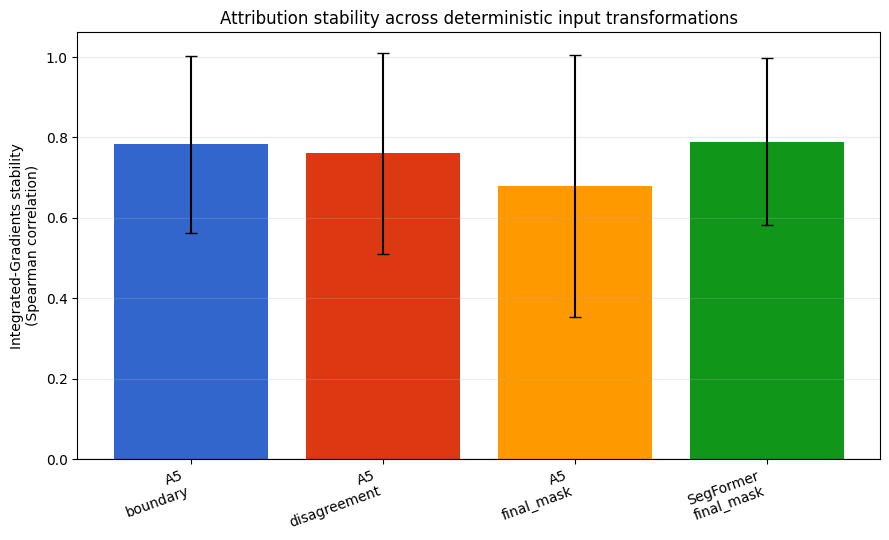


XAI STABILITY AND STATISTICAL ANALYSIS COMPLETE
Stability observations: 192
Paired attribution tests: 8
Paired stability tests: 12

STABILITY SUMMARY


,model,target,transform,cases,mean_spearman_stability,std_spearman_stability,mean_cosine_stability,mean_top10_attribution_iou
0,A5,boundary,brightness_minus_5_percent,12,0.995909,0.004811,0.996817,0.927656
1,A5,boundary,brightness_plus_5_percent,12,0.997759,0.002218,0.998313,0.950223
2,A5,boundary,horizontal_flip,12,0.567243,0.050050,0.648732,0.273780
3,A5,boundary,vertical_flip,12,0.569517,0.077612,0.661831,0.300608
4,A5,disagreement,brightness_minus_5_percent,12,0.995400,0.005285,0.995768,0.907311
5,A5,disagreement,brightness_plus_5_percent,12,0.997403,0.002634,0.997876,0.930640
6,A5,disagreement,horizontal_flip,12,0.488325,0.104527,0.621289,0.169134
7,A5,disagreement,vertical_flip,12,0.563334,0.106148,0.715586,0.249443
8,A5,final_mask,brightness_minus_5_percent,12,0.993382,0.008059,0.997069,0.909950
9,A5,final_mask,brightness_plus_5_percent,12,0.996539,0.003579,0.998592,0.937450



A5 VERSUS SEGFORMER XAI


,method,metric,paired_cases,a5_mean,segformer_mean,difference_a5_minus_segformer,ci95_lower,ci95_upper,wilcoxon_statistic,wilcoxon_raw_p,cohens_dz,wilcoxon_holm_p,significant_after_holm_0_05
0,integrated_gradients,deletion_auc,12,0.196899,0.040903,0.155996,0.056464,0.286075,8.0,0.012207,0.713304,0.061035,False
1,integrated_gradients,lesion_concentration,12,0.247656,0.518585,-0.270929,-0.337219,-0.209562,0.0,0.000488,-2.279879,0.003906,True
2,integrated_gradients,boundary_concentration,12,0.094659,0.190800,-0.096141,-0.171254,-0.026398,13.0,0.042480,-0.721274,0.169922,False
3,integrated_gradients,disagreement_concentration,12,0.194838,0.282740,-0.087902,-0.128474,-0.045109,3.0,0.002441,-1.149713,0.017090,True
4,occlusion,deletion_auc,12,0.190272,0.123253,0.067019,-0.083231,0.218482,23.0,0.233398,0.239536,0.528809,False
5,occlusion,lesion_concentration,12,0.361490,0.444275,-0.082785,-0.140136,-0.034348,7.0,0.009277,-0.841400,0.055664,False
6,occlusion,boundary_concentration,12,0.128350,0.098762,0.029588,-0.009791,0.067792,21.0,0.176270,0.410482,0.528809,False
7,occlusion,disagreement_concentration,12,0.231753,0.231847,-0.000093,-0.031247,0.028714,37.0,0.909668,-0.001680,0.909668,False



A5 VERSUS SEGFORMER STABILITY


,transform,metric,paired_cases,a5_mean,segformer_mean,difference_a5_minus_segformer,ci95_lower,ci95_upper,wilcoxon_statistic,wilcoxon_raw_p,cohens_dz,wilcoxon_holm_p,significant_after_holm_0_05
0,horizontal_flip,spearman_stability,12,0.423607,0.618255,-0.194648,-0.246340,-0.145513,0.0,0.000488,-2.050100,0.005859,True
1,horizontal_flip,cosine_stability,12,0.684328,0.780859,-0.096532,-0.117997,-0.072939,1.0,0.000977,-2.331647,0.005859,True
2,horizontal_flip,top10_attribution_iou,12,0.172275,0.428527,-0.256252,-0.337806,-0.181941,0.0,0.000488,-1.785981,0.005859,True
3,vertical_flip,spearman_stability,12,0.300167,0.568741,-0.268574,-0.318510,-0.219584,0.0,0.000488,-2.925654,0.005859,True
4,vertical_flip,cosine_stability,12,0.636879,0.731417,-0.094538,-0.118260,-0.070659,0.0,0.000488,-2.112397,0.005859,True
5,vertical_flip,top10_attribution_iou,12,0.113514,0.373835,-0.260321,-0.347603,-0.184663,0.0,0.000488,-1.725116,0.005859,True
6,brightness_minus_5_percent,spearman_stability,12,0.993382,0.984700,0.008682,0.004332,0.014652,0.0,0.000488,0.905064,0.005859,True
7,brightness_minus_5_percent,cosine_stability,12,0.997069,0.991908,0.005162,0.002796,0.007945,0.0,0.000488,1.055468,0.005859,True
8,brightness_minus_5_percent,top10_attribution_iou,12,0.909950,0.874574,0.035376,0.007895,0.060452,12.0,0.034180,0.723533,0.034180,True
9,brightness_plus_5_percent,spearman_stability,12,0.996539,0.987452,0.009087,0.005149,0.013915,0.0,0.000488,1.091246,0.005859,True



Saved figure: /content/drive/MyDrive/MADSeg/outputs/paper_artifacts/figures/XAI_Stability_Summary.png
Saved tables: /content/drive/MyDrive/MADSeg/outputs/paper_artifacts/tables
Figure registry: /content/drive/MyDrive/MADSeg/outputs/paper_artifacts/figure_registry.csv
Table registry: /content/drive/MyDrive/MADSeg/outputs/paper_artifacts/table_registry.csv
Test images accessed: 0
Validation-developed XAI is complete. Ready for final artifact audit before the one-time test evaluation.


In [ ]:
# ============================================================
# XAI BLOCK 3 — STABILITY + PAIRED STATISTICAL SUMMARY
#
# Requires the successful XAI restoration and execution cells.
# Validation cases only; test loader is never accessed.
# ============================================================

import gc
import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import torch
import torch.nn.functional as F

from scipy.stats import spearmanr, wilcoxon
from tqdm.auto import tqdm


# ------------------------------------------------------------
# 1. Requirements and paths
# ------------------------------------------------------------

required_names = [
    "a5_model",
    "segformer_model",
    "case_data",
    "integrated_gradients",
    "build_frozen_rois",
]

missing_names = [
    name
    for name in required_names
    if name not in globals()
]

assert not missing_names, (
    f"Missing XAI definitions: {missing_names}. "
    "Rerun the corrected restoration gate and "
    "XAI execution block first."
)

OUTPUT_ROOT = Path(
    "/content/drive/MyDrive/MADSeg/outputs"
)

XAI_ROOT = OUTPUT_ROOT / "xai"

PAPER_ROOT = (
    OUTPUT_ROOT / "paper_artifacts"
)

FIGURE_ROOT = PAPER_ROOT / "figures"
TABLE_ROOT = PAPER_ROOT / "tables"

FIGURE_REGISTRY_PATH = (
    PAPER_ROOT / "figure_registry.csv"
)

TABLE_REGISTRY_PATH = (
    PAPER_ROOT / "table_registry.csv"
)

RAW_ATTRIBUTION_ROOT = (
    XAI_ROOT / "raw_attributions"
)

STABILITY_RAW_ROOT = (
    XAI_ROOT / "stability_raw"
)

STABILITY_CASE_ROOT = (
    XAI_ROOT / "stability_case_results"
)

for directory in [
    FIGURE_ROOT,
    TABLE_ROOT,
    STABILITY_RAW_ROOT,
    STABILITY_CASE_ROOT,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )

CASE_MANIFEST_PATH = (
    XAI_ROOT
    / "xai_validation_case_manifest.csv"
)

ATTRIBUTION_METRICS_PATH = (
    XAI_ROOT
    / "xai_attribution_metrics.csv"
)

STABILITY_METRICS_PATH = (
    TABLE_ROOT
    / "XAI_stability_per_case.csv"
)

STABILITY_SUMMARY_PATH = (
    TABLE_ROOT
    / "XAI_stability_summary.csv"
)

PAIRED_XAI_PATH = (
    TABLE_ROOT
    / "XAI_A5_vs_SegFormer_paired.csv"
)

PAIRED_STABILITY_PATH = (
    TABLE_ROOT
    / "XAI_A5_vs_SegFormer_stability_paired.csv"
)

STABILITY_FIGURE_PATH = (
    FIGURE_ROOT
    / "XAI_Stability_Summary.png"
)

FINAL_SUMMARY_PATH = (
    XAI_ROOT
    / "xai_stability_statistical_summary.json"
)

IG_STEPS = 64
IG_BATCH_SIZE = 8
BOOTSTRAP_REPETITIONS = 5000
BOOTSTRAP_SEED = 4201

device = torch.device("cuda")

case_manifest = pd.read_csv(
    CASE_MANIFEST_PATH
)

selected_ids = [
    str(value).strip()
    for value in case_manifest["isic_id"]
]

assert len(selected_ids) == 12

a5_model.eval()
segformer_model.eval()


# ------------------------------------------------------------
# 2. Transform definitions
# ------------------------------------------------------------

IMAGENET_MEAN_GPU = torch.tensor(
    [0.485, 0.456, 0.406],
    device=device,
).view(1, 3, 1, 1)

IMAGENET_STD_GPU = torch.tensor(
    [0.229, 0.224, 0.225],
    device=device,
).view(1, 3, 1, 1)


def brightness_transform(image, factor):
    rgb = (
        image * IMAGENET_STD_GPU
        + IMAGENET_MEAN_GPU
    )

    rgb = (
        rgb * factor
    ).clamp(0.0, 1.0)

    return (
        rgb - IMAGENET_MEAN_GPU
    ) / IMAGENET_STD_GPU


TRANSFORM_NAMES = [
    "horizontal_flip",
    "vertical_flip",
    "brightness_minus_5_percent",
    "brightness_plus_5_percent",
]


def apply_transform(image, roi, name):
    if name == "horizontal_flip":
        return (
            torch.flip(image, dims=[-1]),
            torch.flip(roi, dims=[-1]),
        )

    if name == "vertical_flip":
        return (
            torch.flip(image, dims=[-2]),
            torch.flip(roi, dims=[-2]),
        )

    if name == "brightness_minus_5_percent":
        return (
            brightness_transform(
                image,
                0.95,
            ),
            roi,
        )

    if name == "brightness_plus_5_percent":
        return (
            brightness_transform(
                image,
                1.05,
            ),
            roi,
        )

    raise ValueError(name)


def inverse_transform_map(
    attribution,
    name,
):
    if name == "horizontal_flip":
        return torch.flip(
            attribution,
            dims=[-1],
        )

    if name == "vertical_flip":
        return torch.flip(
            attribution,
            dims=[-2],
        )

    return attribution


# ------------------------------------------------------------
# 3. Stability metrics
# ------------------------------------------------------------

def safe_spearman(first, second):
    first = np.asarray(
        first,
        dtype=np.float64,
    ).reshape(-1)

    second = np.asarray(
        second,
        dtype=np.float64,
    ).reshape(-1)

    if (
        np.ptp(first) == 0
        or np.ptp(second) == 0
    ):
        return 0.0

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")

        value = spearmanr(
            first,
            second,
        ).statistic

    if not np.isfinite(value):
        return 0.0

    return float(value)


def cosine_similarity(first, second):
    first = first.flatten().float()
    second = second.flatten().float()

    denominator = (
        torch.linalg.vector_norm(first)
        * torch.linalg.vector_norm(second)
    )

    if denominator <= 0:
        return 0.0

    return float(
        torch.dot(first, second)
        .div(denominator)
        .cpu()
    )


def top_fraction_iou(
    first,
    second,
    fraction=0.10,
):
    first = first.flatten().abs()
    second = second.flatten().abs()

    number_selected = max(
        1,
        int(round(
            fraction * first.numel()
        )),
    )

    first_indices = torch.topk(
        first,
        number_selected,
    ).indices

    second_indices = torch.topk(
        second,
        number_selected,
    ).indices

    first_mask = torch.zeros(
        first.numel(),
        dtype=torch.bool,
        device=first.device,
    )

    second_mask = torch.zeros_like(
        first_mask
    )

    first_mask[first_indices] = True
    second_mask[second_indices] = True

    intersection = (
        first_mask & second_mask
    ).sum().item()

    union = (
        first_mask | second_mask
    ).sum().item()

    return float(
        intersection / max(union, 1)
    )


TARGETS = [
    ("A5", "final_mask"),
    ("A5", "boundary"),
    ("A5", "disagreement"),
    ("SegFormer", "final_mask"),
]


# ------------------------------------------------------------
# 4. Compute transformation stability
# ------------------------------------------------------------

stability_records = []

for isic_id in tqdm(
    selected_ids,
    desc="Frozen XAI stability",
):
    case_result_path = (
        STABILITY_CASE_ROOT
        / f"{isic_id}.json"
    )

    transformed_raw_path = (
        STABILITY_RAW_ROOT
        / f"{isic_id}.npz"
    )

    if (
        case_result_path.exists()
        and transformed_raw_path.exists()
    ):
        with open(
            case_result_path,
            "r",
            encoding="utf-8",
        ) as file:
            saved_case = json.load(file)

        stability_records.extend(
            saved_case["records"]
        )

        continue

    image = (
        case_data[isic_id]["image"]
        .to(device)
        .float()
    )

    frozen_rois = build_frozen_rois(
        image
    )

    original_raw_path = (
        RAW_ATTRIBUTION_ROOT
        / f"{isic_id}.npz"
    )

    assert original_raw_path.exists()

    original_arrays = np.load(
        original_raw_path
    )

    case_records = []
    transformed_arrays = {}

    for model_name, target_name in TARGETS:
        original_key = (
            f"{model_name}_{target_name}_ig"
        )

        assert original_key in original_arrays

        original_attribution = (
            torch.from_numpy(
                original_arrays[original_key]
            )
            .to(device)
            .float()
        )

        frozen_roi = frozen_rois[
            (model_name, target_name)
        ]

        for transform_name in TRANSFORM_NAMES:
            (
                transformed_image,
                transformed_roi,
            ) = apply_transform(
                image,
                frozen_roi,
                transform_name,
            )

            transformed_attribution = (
                integrated_gradients(
                    model_name,
                    target_name,
                    transformed_image,
                    transformed_roi,
                    steps=IG_STEPS,
                    internal_batch_size=
                        IG_BATCH_SIZE,
                )
            )

            aligned_attribution = (
                inverse_transform_map(
                    transformed_attribution,
                    transform_name,
                )
            )

            spearman_value = safe_spearman(
                original_attribution
                .detach()
                .cpu()
                .numpy(),
                aligned_attribution
                .detach()
                .cpu()
                .numpy(),
            )

            cosine_value = cosine_similarity(
                original_attribution,
                aligned_attribution,
            )

            top10_iou = top_fraction_iou(
                original_attribution,
                aligned_attribution,
                fraction=0.10,
            )

            case_records.append({
                "isic_id": isic_id,
                "model": model_name,
                "target": target_name,
                "method":
                    "integrated_gradients",
                "transform": transform_name,
                "spearman_stability":
                    spearman_value,
                "cosine_stability":
                    cosine_value,
                "top10_attribution_iou":
                    top10_iou,
            })

            transformed_key = (
                f"{model_name}_{target_name}_"
                f"{transform_name}"
            )

            transformed_arrays[
                transformed_key
            ] = (
                aligned_attribution
                .detach()
                .cpu()
                .numpy()
            )

            del transformed_image
            del transformed_attribution
            del aligned_attribution

        del original_attribution

    np.savez_compressed(
        transformed_raw_path,
        **transformed_arrays,
    )

    case_payload = {
        "isic_id": isic_id,
        "split": "validation",
        "records": case_records,
        "raw_file": str(
            transformed_raw_path
        ),
        "test_images_accessed": 0,
    }

    with open(
        case_result_path,
        "w",
        encoding="utf-8",
    ) as file:
        json.dump(
            case_payload,
            file,
            indent=2,
        )

    stability_records.extend(
        case_records
    )

    del image
    del frozen_rois
    original_arrays.close()

    gc.collect()
    torch.cuda.empty_cache()


stability_frame = pd.DataFrame(
    stability_records
)

expected_rows = (
    12
    * len(TARGETS)
    * len(TRANSFORM_NAMES)
)

assert len(stability_frame) == expected_rows
assert stability_frame[
    "isic_id"
].nunique() == 12

stability_frame.to_csv(
    STABILITY_METRICS_PATH,
    index=False,
)


# ------------------------------------------------------------
# 5. Stability summary
# ------------------------------------------------------------

stability_summary = (
    stability_frame
    .groupby(
        [
            "model",
            "target",
            "transform",
        ],
        as_index=False,
    )
    .agg(
        cases=("isic_id", "count"),
        mean_spearman_stability=(
            "spearman_stability",
            "mean",
        ),
        std_spearman_stability=(
            "spearman_stability",
            "std",
        ),
        mean_cosine_stability=(
            "cosine_stability",
            "mean",
        ),
        mean_top10_attribution_iou=(
            "top10_attribution_iou",
            "mean",
        ),
    )
)

stability_summary.to_csv(
    STABILITY_SUMMARY_PATH,
    index=False,
)


# ------------------------------------------------------------
# 6. Statistical helpers for 12 paired cases
# ------------------------------------------------------------

bootstrap_generator = np.random.default_rng(
    BOOTSTRAP_SEED
)

bootstrap_indices = (
    bootstrap_generator.integers(
        0,
        12,
        size=(
            BOOTSTRAP_REPETITIONS,
            12,
        ),
    )
)


def paired_statistics(differences):
    differences = np.asarray(
        differences,
        dtype=np.float64,
    )

    assert len(differences) == 12

    bootstrap_means = (
        differences[bootstrap_indices]
        .mean(axis=1)
    )

    lower = float(
        np.percentile(
            bootstrap_means,
            2.5,
        )
    )

    upper = float(
        np.percentile(
            bootstrap_means,
            97.5,
        )
    )

    if np.allclose(differences, 0):
        statistic = 0.0
        p_value = 1.0

    else:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")

            result = wilcoxon(
                differences,
                alternative="two-sided",
                method="auto",
            )

        statistic = float(
            result.statistic
        )

        p_value = float(
            result.pvalue
        )

    standard_deviation = differences.std(
        ddof=1
    )

    effect_dz = (
        float(
            differences.mean()
            / standard_deviation
        )
        if standard_deviation > 0
        else 0.0
    )

    return {
        "mean_difference": float(
            differences.mean()
        ),
        "ci95_lower": lower,
        "ci95_upper": upper,
        "wilcoxon_statistic":
            statistic,
        "wilcoxon_raw_p": p_value,
        "cohens_dz": effect_dz,
    }


def holm_adjust(p_values):
    p_values = np.asarray(
        p_values,
        dtype=np.float64,
    )

    count = len(p_values)
    order = np.argsort(p_values)
    ordered = p_values[order]

    ordered_adjusted = np.empty(count)
    running_maximum = 0.0

    for position, p_value in enumerate(
        ordered
    ):
        adjusted_value = (
            count - position
        ) * p_value

        running_maximum = max(
            running_maximum,
            adjusted_value,
        )

        ordered_adjusted[position] = min(
            1.0,
            running_maximum,
        )

    adjusted = np.empty(count)
    adjusted[order] = ordered_adjusted

    return adjusted


# ------------------------------------------------------------
# 7. A5 versus SegFormer attribution comparisons
# ------------------------------------------------------------

attribution_frame = pd.read_csv(
    ATTRIBUTION_METRICS_PATH
)

comparison_metrics = [
    "deletion_auc",
    "lesion_concentration",
    "boundary_concentration",
    "disagreement_concentration",
]

paired_records = []

for method_name in [
    "integrated_gradients",
    "occlusion",
]:
    a5_subset = attribution_frame[
        (
            attribution_frame["model"]
            == "A5"
        )
        & (
            attribution_frame["target"]
            == "final_mask"
        )
        & (
            attribution_frame["method"]
            == method_name
        )
    ]

    comparator_subset = attribution_frame[
        (
            attribution_frame["model"]
            == "SegFormer"
        )
        & (
            attribution_frame["target"]
            == "final_mask"
        )
        & (
            attribution_frame["method"]
            == method_name
        )
    ]

    paired = a5_subset.merge(
        comparator_subset,
        on="isic_id",
        suffixes=("_a5", "_segformer"),
        validate="one_to_one",
    )

    assert len(paired) == 12

    for metric in comparison_metrics:
        a5_values = paired[
            f"{metric}_a5"
        ].to_numpy()

        comparator_values = paired[
            f"{metric}_segformer"
        ].to_numpy()

        differences = (
            a5_values - comparator_values
        )

        statistics = paired_statistics(
            differences
        )

        paired_records.append({
            "method": method_name,
            "metric": metric,
            "paired_cases": 12,
            "a5_mean": float(
                a5_values.mean()
            ),
            "segformer_mean": float(
                comparator_values.mean()
            ),
            "difference_a5_minus_segformer":
                statistics[
                    "mean_difference"
                ],
            "ci95_lower":
                statistics["ci95_lower"],
            "ci95_upper":
                statistics["ci95_upper"],
            "wilcoxon_statistic":
                statistics[
                    "wilcoxon_statistic"
                ],
            "wilcoxon_raw_p":
                statistics[
                    "wilcoxon_raw_p"
                ],
            "cohens_dz":
                statistics["cohens_dz"],
        })


paired_xai_frame = pd.DataFrame(
    paired_records
)

paired_xai_frame[
    "wilcoxon_holm_p"
] = holm_adjust(
    paired_xai_frame[
        "wilcoxon_raw_p"
    ].to_numpy()
)

paired_xai_frame[
    "significant_after_holm_0_05"
] = (
    paired_xai_frame[
        "wilcoxon_holm_p"
    ] < 0.05
)

paired_xai_frame.to_csv(
    PAIRED_XAI_PATH,
    index=False,
)


# ------------------------------------------------------------
# 8. Paired stability comparisons
# ------------------------------------------------------------

paired_stability_records = []

for transform_name in TRANSFORM_NAMES:
    a5_subset = stability_frame[
        (
            stability_frame["model"]
            == "A5"
        )
        & (
            stability_frame["target"]
            == "final_mask"
        )
        & (
            stability_frame["transform"]
            == transform_name
        )
    ]

    comparator_subset = stability_frame[
        (
            stability_frame["model"]
            == "SegFormer"
        )
        & (
            stability_frame["target"]
            == "final_mask"
        )
        & (
            stability_frame["transform"]
            == transform_name
        )
    ]

    paired = a5_subset.merge(
        comparator_subset,
        on="isic_id",
        suffixes=("_a5", "_segformer"),
        validate="one_to_one",
    )

    assert len(paired) == 12

    for metric in [
        "spearman_stability",
        "cosine_stability",
        "top10_attribution_iou",
    ]:
        a5_values = paired[
            f"{metric}_a5"
        ].to_numpy()

        comparator_values = paired[
            f"{metric}_segformer"
        ].to_numpy()

        differences = (
            a5_values
            - comparator_values
        )

        statistics = paired_statistics(
            differences
        )

        paired_stability_records.append({
            "transform": transform_name,
            "metric": metric,
            "paired_cases": 12,
            "a5_mean": float(
                a5_values.mean()
            ),
            "segformer_mean": float(
                comparator_values.mean()
            ),
            "difference_a5_minus_segformer":
                statistics[
                    "mean_difference"
                ],
            "ci95_lower":
                statistics["ci95_lower"],
            "ci95_upper":
                statistics["ci95_upper"],
            "wilcoxon_statistic":
                statistics[
                    "wilcoxon_statistic"
                ],
            "wilcoxon_raw_p":
                statistics[
                    "wilcoxon_raw_p"
                ],
            "cohens_dz":
                statistics["cohens_dz"],
        })


paired_stability_frame = pd.DataFrame(
    paired_stability_records
)

paired_stability_frame[
    "wilcoxon_holm_p"
] = holm_adjust(
    paired_stability_frame[
        "wilcoxon_raw_p"
    ].to_numpy()
)

paired_stability_frame[
    "significant_after_holm_0_05"
] = (
    paired_stability_frame[
        "wilcoxon_holm_p"
    ] < 0.05
)

paired_stability_frame.to_csv(
    PAIRED_STABILITY_PATH,
    index=False,
)


# ------------------------------------------------------------
# 9. Central stability figure
# ------------------------------------------------------------

plot_frame = (
    stability_frame
    .groupby(
        ["model", "target"],
        as_index=False,
    )
    .agg(
        mean_spearman=(
            "spearman_stability",
            "mean",
        ),
        std_spearman=(
            "spearman_stability",
            "std",
        ),
    )
)

plot_frame["label"] = (
    plot_frame["model"]
    + "\n"
    + plot_frame["target"]
)

figure, axis = plt.subplots(
    figsize=(9, 5.5)
)

positions = np.arange(
    len(plot_frame)
)

axis.bar(
    positions,
    plot_frame["mean_spearman"],
    yerr=plot_frame["std_spearman"],
    capsize=4,
    color=[
        "#3366cc",
        "#dc3912",
        "#ff9900",
        "#109618",
    ],
)

axis.set_xticks(positions)
axis.set_xticklabels(
    plot_frame["label"],
    rotation=20,
    ha="right",
)

axis.set_ylabel(
    "Integrated-Gradients stability\n"
    "(Spearman correlation)"
)

axis.set_title(
    "Attribution stability across deterministic "
    "input transformations"
)

axis.axhline(
    0,
    color="black",
    linewidth=0.8,
)

axis.grid(
    axis="y",
    alpha=0.25,
)

figure.tight_layout()

figure.savefig(
    STABILITY_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close(figure)


# ------------------------------------------------------------
# 10. Update centralized registries
# ------------------------------------------------------------

def update_registry(
    registry_path,
    new_records,
):
    new_frame = pd.DataFrame(
        new_records
    )

    if registry_path.exists():
        existing = pd.read_csv(
            registry_path
        )

        all_columns = list(
            dict.fromkeys(
                list(existing.columns)
                + list(new_frame.columns)
            )
        )

        existing = existing.reindex(
            columns=all_columns
        )

        new_frame = new_frame.reindex(
            columns=all_columns
        )

        existing = existing[
            ~existing["artifact_id"].isin(
                new_frame["artifact_id"]
            )
        ]

        combined = pd.concat(
            [existing, new_frame],
            ignore_index=True,
        )

    else:
        combined = new_frame

    combined.to_csv(
        registry_path,
        index=False,
    )


update_registry(
    FIGURE_REGISTRY_PATH,
    [{
        "artifact_id":
            "XAI_Stability_Summary",
        "final_figure_number": "TBD",
        "short_name":
            "XAI stability summary",
        "filename":
            STABILITY_FIGURE_PATH.name,
        "source_file":
            str(STABILITY_METRICS_PATH),
        "source_experiment":
            "Frozen A5-SegFormer XAI",
        "split": "validation",
        "selection_rule":
            "Frozen 12-case XAI manifest",
        "caption_draft": (
            "Integrated-Gradients stability under "
            "flips and mild brightness changes."
        ),
        "manuscript_section":
            "Explainable AI",
        "status":
            "candidate manuscript figure",
        "notes":
            "Error bars show variation over cases "
            "and transformations.",
    }],
)

new_table_records = []

for artifact_id, path, short_name in [
    (
        "XAI_Table_Stability_Per_Case",
        STABILITY_METRICS_PATH,
        "Per-case XAI stability",
    ),
    (
        "XAI_Table_Stability_Summary",
        STABILITY_SUMMARY_PATH,
        "XAI stability summary",
    ),
    (
        "XAI_Table_Paired_Model_Comparison",
        PAIRED_XAI_PATH,
        "Paired A5-SegFormer XAI comparison",
    ),
    (
        "XAI_Table_Paired_Stability",
        PAIRED_STABILITY_PATH,
        "Paired A5-SegFormer stability",
    ),
]:
    new_table_records.append({
        "artifact_id": artifact_id,
        "final_table_number": "TBD",
        "short_name": short_name,
        "filename": path.name,
        "source_file": str(path),
        "source_experiment":
            "Frozen A5-SegFormer XAI",
        "split": "validation",
        "selection_rule":
            "Frozen 12-case manifest",
        "caption_draft": short_name,
        "manuscript_section":
            "Explainable AI",
        "status":
            "candidate/supporting table",
        "notes": (
            "Exploratory paired inference over "
            "12 deliberately selected cases."
        ),
    })

update_registry(
    TABLE_REGISTRY_PATH,
    new_table_records,
)


# ------------------------------------------------------------
# 11. Save final XAI summary
# ------------------------------------------------------------

summary_payload = {
    "validation_cases": 12,
    "stability_transformations":
        TRANSFORM_NAMES,
    "integrated_gradients_steps":
        IG_STEPS,
    "stability_rows":
        int(len(stability_frame)),
    "paired_attribution_tests":
        int(len(paired_xai_frame)),
    "paired_stability_tests":
        int(
            len(paired_stability_frame)
        ),
    "multiple_testing":
        "Holm correction",
    "inference_scope": (
        "Exploratory inference over a "
        "deliberately stratified 12-case "
        "validation sample."
    ),
    "test_images_accessed": 0,
    "artifacts": {
        "stability_per_case":
            str(STABILITY_METRICS_PATH),
        "stability_summary":
            str(STABILITY_SUMMARY_PATH),
        "paired_xai":
            str(PAIRED_XAI_PATH),
        "paired_stability":
            str(PAIRED_STABILITY_PATH),
        "stability_figure":
            str(STABILITY_FIGURE_PATH),
    },
}

with open(
    FINAL_SUMMARY_PATH,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        summary_payload,
        file,
        indent=2,
    )


# ------------------------------------------------------------
# 12. Final report
# ------------------------------------------------------------

print(
    "\nXAI STABILITY AND STATISTICAL "
    "ANALYSIS COMPLETE"
)

print(
    "Stability observations:",
    len(stability_frame),
)

print(
    "Paired attribution tests:",
    len(paired_xai_frame),
)

print(
    "Paired stability tests:",
    len(paired_stability_frame),
)

print("\nSTABILITY SUMMARY")
display(stability_summary)

print("\nA5 VERSUS SEGFORMER XAI")
display(paired_xai_frame)

print("\nA5 VERSUS SEGFORMER STABILITY")
display(paired_stability_frame)

print("\nSaved figure:", STABILITY_FIGURE_PATH)
print("Saved tables:", TABLE_ROOT)
print("Figure registry:", FIGURE_REGISTRY_PATH)
print("Table registry:", TABLE_REGISTRY_PATH)
print("Test images accessed: 0")
print(
    "Validation-developed XAI is complete. "
    "Ready for final artifact audit before "
    "the one-time test evaluation."
)

In [ ]:
# ============================================================
# FINAL ARTIFACT AND TEST-READINESS AUDIT
#
# This block DOES NOT iterate or inspect the test loader.
# It only verifies frozen artifacts and creates an unlock file.
# ============================================================

import hashlib
import json
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
import torch


# ------------------------------------------------------------
# 1. Paths
# ------------------------------------------------------------

OUTPUT_ROOT = Path(
    "/content/drive/MyDrive/MADSeg/outputs"
)

FREEZE_ROOT = (
    OUTPUT_ROOT / "final_experiment_freeze"
)

FREEZE_MANIFEST_PATH = (
    FREEZE_ROOT / "experiment_freeze_v1.json"
)

TEST_READINESS_REPORT_PATH = (
    FREEZE_ROOT / "test_readiness_audit.csv"
)

TEST_READINESS_JSON_PATH = (
    FREEZE_ROOT / "test_readiness_audit.json"
)

TEST_UNLOCK_PATH = (
    FREEZE_ROOT
    / "test_evaluation_unlock_v1.json"
)

FINAL_TEST_ROOT = (
    OUTPUT_ROOT / "final_test_evaluation"
)

PAPER_ROOT = (
    OUTPUT_ROOT / "paper_artifacts"
)

FIGURE_ROOT = PAPER_ROOT / "figures"
TABLE_ROOT = PAPER_ROOT / "tables"

FIGURE_REGISTRY_PATH = (
    PAPER_ROOT / "figure_registry.csv"
)

TABLE_REGISTRY_PATH = (
    PAPER_ROOT / "table_registry.csv"
)

A5_VALIDATION_METRICS = (
    OUTPUT_ROOT
    / "madseg_ablations"
    / "A5"
    / "validation_evaluation"
    / "per_image_metrics.csv"
)

SEGFORMER_VALIDATION_METRICS = (
    OUTPUT_ROOT
    / "architecture_baselines"
    / "baseline_segformer_seed442"
    / "validation_evaluation"
    / "per_image_metrics.csv"
)

XAI_ROOT = OUTPUT_ROOT / "xai"

XAI_CASE_MANIFEST = (
    XAI_ROOT
    / "xai_validation_case_manifest.csv"
)

XAI_ATTRIBUTION_METRICS = (
    XAI_ROOT
    / "xai_attribution_metrics.csv"
)

XAI_DELETION_CURVES = (
    XAI_ROOT
    / "xai_deletion_curves.csv"
)

XAI_STABILITY_METRICS = (
    TABLE_ROOT
    / "XAI_stability_per_case.csv"
)

XAI_PAIRED_ATTRIBUTION = (
    TABLE_ROOT
    / "XAI_A5_vs_SegFormer_paired.csv"
)

XAI_PAIRED_STABILITY = (
    TABLE_ROOT
    / "XAI_A5_vs_SegFormer_stability_paired.csv"
)

XAI_STABILITY_FIGURE = (
    FIGURE_ROOT
    / "XAI_Stability_Summary.png"
)


# ------------------------------------------------------------
# 2. Check framework
# ------------------------------------------------------------

audit_records = []


def add_check(
    check_name,
    passed,
    observed,
    expected,
    severity="critical",
):
    audit_records.append({
        "check_name": check_name,
        "passed": bool(passed),
        "severity": severity,
        "observed": str(observed),
        "expected": str(expected),
    })

    symbol = "PASS" if passed else "FAIL"

    print(
        f"[{symbol}] {check_name}: "
        f"{observed}"
    )


def sha256_file(
    path,
    chunk_size=8 * 1024 * 1024,
):
    digest = hashlib.sha256()

    with open(path, "rb") as file:
        while True:
            chunk = file.read(chunk_size)

            if not chunk:
                break

            digest.update(chunk)

    return digest.hexdigest()


# ------------------------------------------------------------
# 3. Freeze-manifest checks
# ------------------------------------------------------------

add_check(
    "freeze_manifest_exists",
    FREEZE_MANIFEST_PATH.exists(),
    FREEZE_MANIFEST_PATH.exists(),
    True,
)

assert FREEZE_MANIFEST_PATH.exists(), (
    "Freeze manifest is missing."
)

with open(
    FREEZE_MANIFEST_PATH,
    "r",
    encoding="utf-8",
) as file:
    freeze_manifest = json.load(file)

add_check(
    "primary_model_frozen",
    freeze_manifest.get(
        "primary_model"
    ) == "A5",
    freeze_manifest.get(
        "primary_model"
    ),
    "A5",
)

add_check(
    "external_comparator_frozen",
    freeze_manifest.get(
        "external_comparator"
    ) == "SegFormer",
    freeze_manifest.get(
        "external_comparator"
    ),
    "SegFormer",
)

add_check(
    "primary_endpoint_frozen",
    freeze_manifest.get(
        "primary_endpoint"
    ) == "per-image expected-human Dice",
    freeze_manifest.get(
        "primary_endpoint"
    ),
    "per-image expected-human Dice",
)

add_check(
    "operating_threshold_frozen",
    float(
        freeze_manifest.get(
            "operating_threshold",
            np.nan,
        )
    ) == 0.5,
    freeze_manifest.get(
        "operating_threshold"
    ),
    0.5,
)

add_check(
    "training_seed_frozen",
    int(
        freeze_manifest.get(
            "training_seed",
            -1,
        )
    ) == 442,
    freeze_manifest.get(
        "training_seed"
    ),
    442,
)

add_check(
    "test_not_previously_marked_complete",
    not bool(
        freeze_manifest.get(
            "test_evaluation_performed",
            False,
        )
    ),
    freeze_manifest.get(
        "test_evaluation_performed",
        False,
    ),
    False,
)


# ------------------------------------------------------------
# 4. Frozen checkpoint hashes
# ------------------------------------------------------------

model_artifacts = freeze_manifest[
    "model_artifacts"
]

A5_CHECKPOINT = Path(
    model_artifacts["A5"]["checkpoint"]
)

SEGFORMER_CHECKPOINT = Path(
    model_artifacts[
        "SegFormer"
    ]["checkpoint"]
)

for model_name, checkpoint_path in [
    ("A5", A5_CHECKPOINT),
    (
        "SegFormer",
        SEGFORMER_CHECKPOINT,
    ),
]:
    exists = checkpoint_path.exists()

    add_check(
        f"{model_name}_checkpoint_exists",
        exists,
        exists,
        True,
    )

    if not exists:
        continue

    actual_hash = sha256_file(
        checkpoint_path
    )

    expected_hash = model_artifacts[
        model_name
    ]["checkpoint_sha256"]

    add_check(
        f"{model_name}_checkpoint_hash",
        actual_hash == expected_hash,
        actual_hash,
        expected_hash,
    )


# ------------------------------------------------------------
# 5. Checkpoint metadata
# ------------------------------------------------------------

def inspect_checkpoint(
    model_name,
    checkpoint_path,
    expected_epoch,
):
    if not checkpoint_path.exists():
        return

    checkpoint = torch.load(
        checkpoint_path,
        map_location="cpu",
        weights_only=False,
    )

    epoch = checkpoint.get(
        "epoch",
        checkpoint.get("best_epoch"),
    )

    add_check(
        f"{model_name}_checkpoint_epoch",
        int(epoch) == expected_epoch,
        epoch,
        expected_epoch,
    )

    test_flags = []

    for key in [
        "test_evaluated",
        "test_set_evaluated",
        "test_evaluation_performed",
    ]:
        if key in checkpoint:
            test_flags.append(
                bool(checkpoint[key])
            )

    add_check(
        f"{model_name}_checkpoint_test_flags",
        not any(test_flags),
        test_flags,
        "all False or absent",
    )

    add_check(
        f"{model_name}_state_dictionary",
        "model_state" in checkpoint,
        "model_state" in checkpoint,
        True,
    )


inspect_checkpoint(
    "A5",
    A5_CHECKPOINT,
    expected_epoch=14,
)

inspect_checkpoint(
    "SegFormer",
    SEGFORMER_CHECKPOINT,
    expected_epoch=30,
)


# ------------------------------------------------------------
# 6. Validation prediction alignment
# ------------------------------------------------------------

for name, path in [
    (
        "A5_validation_metrics",
        A5_VALIDATION_METRICS,
    ),
    (
        "SegFormer_validation_metrics",
        SEGFORMER_VALIDATION_METRICS,
    ),
]:
    add_check(
        f"{name}_exists",
        path.exists(),
        path.exists(),
        True,
    )

assert A5_VALIDATION_METRICS.exists()
assert SEGFORMER_VALIDATION_METRICS.exists()


def load_per_image_metrics(path):
    frame = pd.read_csv(path)

    if (
        "ISIC_id" in frame.columns
        and "isic_id" not in frame.columns
    ):
        frame = frame.rename(
            columns={"ISIC_id": "isic_id"}
        )

    assert "isic_id" in frame.columns
    assert "expected_human_dice" in (
        frame.columns
    )

    frame["isic_id"] = (
        frame["isic_id"]
        .astype(str)
        .str.strip()
    )

    return frame


a5_validation_frame = (
    load_per_image_metrics(
        A5_VALIDATION_METRICS
    )
)

segformer_validation_frame = (
    load_per_image_metrics(
        SEGFORMER_VALIDATION_METRICS
    )
)

for name, frame in [
    ("A5", a5_validation_frame),
    (
        "SegFormer",
        segformer_validation_frame,
    ),
]:
    add_check(
        f"{name}_validation_row_count",
        len(frame) == 240,
        len(frame),
        240,
    )

    add_check(
        f"{name}_validation_unique_ids",
        frame["isic_id"].nunique() == 240,
        frame["isic_id"].nunique(),
        240,
    )

    if "split" in frame.columns:
        observed_splits = sorted(
            frame["split"]
            .astype(str)
            .str.lower()
            .unique()
            .tolist()
        )

        add_check(
            f"{name}_validation_split_only",
            observed_splits
            == ["validation"],
            observed_splits,
            ["validation"],
        )

aligned_ids = (
    set(a5_validation_frame["isic_id"])
    == set(
        segformer_validation_frame[
            "isic_id"
        ]
    )
)

add_check(
    "frozen_model_validation_id_alignment",
    aligned_ids,
    aligned_ids,
    True,
)

a5_dice = float(
    a5_validation_frame[
        "expected_human_dice"
    ].mean()
)

segformer_dice = float(
    segformer_validation_frame[
        "expected_human_dice"
    ].mean()
)

add_check(
    "A5_locked_validation_dice",
    abs(a5_dice - 0.851586) < 1e-5,
    f"{a5_dice:.9f}",
    "0.851586 ± 1e-5",
)

add_check(
    "SegFormer_locked_validation_dice",
    abs(
        segformer_dice - 0.849793
    ) < 1e-5,
    f"{segformer_dice:.9f}",
    "0.849793 ± 1e-5",
)


# ------------------------------------------------------------
# 7. Validation-metric file hashes
# ------------------------------------------------------------

for model_name, metric_path in [
    ("A5", A5_VALIDATION_METRICS),
    (
        "SegFormer",
        SEGFORMER_VALIDATION_METRICS,
    ),
]:
    expected_hash = model_artifacts[
        model_name
    ].get(
        "validation_metrics_sha256"
    )

    if expected_hash is None:
        add_check(
            f"{model_name}_validation_hash",
            True,
            "not stored",
            "optional",
            severity="advisory",
        )
    else:
        actual_hash = sha256_file(
            metric_path
        )

        add_check(
            f"{model_name}_validation_hash",
            actual_hash == expected_hash,
            actual_hash,
            expected_hash,
        )


# ------------------------------------------------------------
# 8. XAI completeness
# ------------------------------------------------------------

xai_expected_files = {
    "xai_case_manifest":
        XAI_CASE_MANIFEST,
    "xai_attribution_metrics":
        XAI_ATTRIBUTION_METRICS,
    "xai_deletion_curves":
        XAI_DELETION_CURVES,
    "xai_stability_metrics":
        XAI_STABILITY_METRICS,
    "xai_paired_attribution":
        XAI_PAIRED_ATTRIBUTION,
    "xai_paired_stability":
        XAI_PAIRED_STABILITY,
    "xai_stability_figure":
        XAI_STABILITY_FIGURE,
}

for name, path in xai_expected_files.items():
    add_check(
        f"{name}_exists",
        path.exists(),
        path.exists(),
        True,
    )

assert all(
    path.exists()
    for path in xai_expected_files.values()
)

xai_case_frame = pd.read_csv(
    XAI_CASE_MANIFEST
)

xai_attribution_frame = pd.read_csv(
    XAI_ATTRIBUTION_METRICS
)

xai_deletion_frame = pd.read_csv(
    XAI_DELETION_CURVES
)

xai_stability_frame = pd.read_csv(
    XAI_STABILITY_METRICS
)

xai_paired_attribution_frame = (
    pd.read_csv(
        XAI_PAIRED_ATTRIBUTION
    )
)

xai_paired_stability_frame = (
    pd.read_csv(
        XAI_PAIRED_STABILITY
    )
)

xai_count_checks = [
    (
        "xai_frozen_cases",
        len(xai_case_frame),
        12,
    ),
    (
        "xai_attribution_rows",
        len(xai_attribution_frame),
        96,
    ),
    (
        "xai_deletion_rows",
        len(xai_deletion_frame),
        576,
    ),
    (
        "xai_stability_rows",
        len(xai_stability_frame),
        192,
    ),
    (
        "xai_paired_attribution_tests",
        len(
            xai_paired_attribution_frame
        ),
        8,
    ),
    (
        "xai_paired_stability_tests",
        len(
            xai_paired_stability_frame
        ),
        12,
    ),
]

for name, observed, expected in (
    xai_count_checks
):
    add_check(
        name,
        observed == expected,
        observed,
        expected,
    )

xai_split_valid = (
    "split" in xai_case_frame.columns
    and set(
        xai_case_frame["split"]
        .astype(str)
        .str.lower()
    ) == {"validation"}
)

add_check(
    "xai_manifest_validation_only",
    xai_split_valid,
    xai_split_valid,
    True,
)


# ------------------------------------------------------------
# 9. Raw XAI arrays and candidate figures
# ------------------------------------------------------------

raw_xai_root = (
    XAI_ROOT / "raw_attributions"
)

raw_xai_files = list(
    raw_xai_root.glob("*.npz")
)

add_check(
    "raw_xai_case_files",
    len(raw_xai_files) == 12,
    len(raw_xai_files),
    12,
)

central_xai_figures = list(
    FIGURE_ROOT.glob(
        "XAI_Candidate_*.png"
    )
)

add_check(
    "central_xai_candidate_figures",
    len(central_xai_figures) == 12,
    len(central_xai_figures),
    12,
)


# ------------------------------------------------------------
# 10. Figure and table registries
# ------------------------------------------------------------

add_check(
    "figure_registry_exists",
    FIGURE_REGISTRY_PATH.exists(),
    FIGURE_REGISTRY_PATH.exists(),
    True,
)

add_check(
    "table_registry_exists",
    TABLE_REGISTRY_PATH.exists(),
    TABLE_REGISTRY_PATH.exists(),
    True,
)

assert FIGURE_REGISTRY_PATH.exists()
assert TABLE_REGISTRY_PATH.exists()

figure_registry = pd.read_csv(
    FIGURE_REGISTRY_PATH
)

table_registry = pd.read_csv(
    TABLE_REGISTRY_PATH
)

add_check(
    "figure_registry_unique_ids",
    not figure_registry[
        "artifact_id"
    ].duplicated().any(),
    figure_registry[
        "artifact_id"
    ].nunique(),
    len(figure_registry),
)

add_check(
    "table_registry_unique_ids",
    not table_registry[
        "artifact_id"
    ].duplicated().any(),
    table_registry[
        "artifact_id"
    ].nunique(),
    len(table_registry),
)


def registry_files_exist(
    registry,
    folder,
):
    missing = []

    for filename in registry[
        "filename"
    ].dropna():
        path = folder / str(filename)

        if not path.exists():
            missing.append(str(path))

    return missing


missing_registered_figures = (
    registry_files_exist(
        figure_registry,
        FIGURE_ROOT,
    )
)

missing_registered_tables = (
    registry_files_exist(
        table_registry,
        TABLE_ROOT,
    )
)

add_check(
    "registered_figure_files_exist",
    not missing_registered_figures,
    missing_registered_figures,
    "none missing",
)

add_check(
    "registered_table_files_exist",
    not missing_registered_tables,
    missing_registered_tables,
    "none missing",
)

add_check(
    "current_registered_figure_count",
    10 <= len(figure_registry) <= 15,
    len(figure_registry),
    "10–15",
    severity="advisory",
)

add_check(
    "current_registered_table_count",
    10 <= len(table_registry) <= 15,
    len(table_registry),
    "10–15 after final test tables",
    severity="advisory",
)


# ------------------------------------------------------------
# 11. Confirm no final test outputs exist
# ------------------------------------------------------------

if FINAL_TEST_ROOT.exists():
    existing_test_files = [
        path
        for path in FINAL_TEST_ROOT.rglob("*")
        if path.is_file()
    ]
else:
    existing_test_files = []

add_check(
    "no_existing_final_test_outputs",
    len(existing_test_files) == 0,
    len(existing_test_files),
    0,
)


# ------------------------------------------------------------
# 12. Save audit report
# ------------------------------------------------------------

audit_frame = pd.DataFrame(
    audit_records
)

critical_failures = audit_frame[
    (
        audit_frame["severity"]
        == "critical"
    )
    & (
        ~audit_frame["passed"]
    )
]

advisory_failures = audit_frame[
    (
        audit_frame["severity"]
        == "advisory"
    )
    & (
        ~audit_frame["passed"]
    )
]

audit_frame.to_csv(
    TEST_READINESS_REPORT_PATH,
    index=False,
)

audit_summary = {
    "created_utc": datetime.now(
        timezone.utc
    ).isoformat(),
    "critical_checks": int(
        (
            audit_frame["severity"]
            == "critical"
        ).sum()
    ),
    "critical_failures": int(
        len(critical_failures)
    ),
    "advisory_failures": int(
        len(advisory_failures)
    ),
    "test_ready": bool(
        len(critical_failures) == 0
    ),
    "test_images_accessed": 0,
    "primary_model": "A5",
    "external_comparator": "SegFormer",
    "primary_endpoint":
        "per-image expected-human Dice",
    "operating_threshold": 0.5,
    "training_seed": 442,
    "audit_report": str(
        TEST_READINESS_REPORT_PATH
    ),
}

with open(
    TEST_READINESS_JSON_PATH,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        audit_summary,
        file,
        indent=2,
    )


# ------------------------------------------------------------
# 13. Stop on any critical failure
# ------------------------------------------------------------

if len(critical_failures) > 0:
    print("\nCRITICAL FAILURES")
    display(critical_failures)

    raise AssertionError(
        f"Test readiness failed with "
        f"{len(critical_failures)} critical "
        f"failure(s). Do not access test data."
    )


# ------------------------------------------------------------
# 14. Create one-time test unlock manifest
# ------------------------------------------------------------

unlock_manifest = {
    "unlock_version": "1.0",
    "created_utc": datetime.now(
        timezone.utc
    ).isoformat(),
    "status": "ready_for_one_time_test_evaluation",
    "primary_model": "A5",
    "primary_model_checkpoint":
        str(A5_CHECKPOINT),
    "primary_model_checkpoint_sha256":
        model_artifacts[
            "A5"
        ]["checkpoint_sha256"],
    "external_comparator": "SegFormer",
    "external_comparator_checkpoint":
        str(SEGFORMER_CHECKPOINT),
    "external_comparator_checkpoint_sha256":
        model_artifacts[
            "SegFormer"
        ]["checkpoint_sha256"],
    "primary_endpoint":
        "per-image expected-human Dice",
    "operating_threshold": 0.5,
    "training_seed": 442,
    "multi_seed_analysis": False,
    "expected_test_images": 479,
    "test_evaluation_completed": False,
    "test_images_accessed_during_audit": 0,
    "readiness_audit":
        str(TEST_READINESS_JSON_PATH),
    "rule": (
        "The final test evaluation may be run once "
        "for the frozen A5 and SegFormer checkpoints. "
        "No configuration, threshold, endpoint, or "
        "case selection may be changed afterward."
    ),
}

with open(
    TEST_UNLOCK_PATH,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        unlock_manifest,
        file,
        indent=2,
    )


# ------------------------------------------------------------
# 15. Register readiness audit table
# ------------------------------------------------------------

new_table_record = pd.DataFrame([{
    "artifact_id":
        "Table_Test_Readiness_Audit",
    "final_table_number": "TBD",
    "short_name":
        "Final test-readiness audit",
    "filename":
        TEST_READINESS_REPORT_PATH.name,
    "source_file":
        str(TEST_READINESS_REPORT_PATH),
    "source_experiment":
        "Final experiment freeze",
    "split": "no test data accessed",
    "selection_rule":
        "All frozen critical checks",
    "caption_draft": (
        "Checkpoint, validation, XAI, and "
        "artifact-integrity checks completed "
        "before opening the test set."
    ),
    "manuscript_section":
        "Reproducibility",
    "status": "supporting table",
    "notes":
        "Created before one-time test evaluation.",
}])

# Copy audit CSV into central table folder.
central_audit_table_path = (
    TABLE_ROOT
    / TEST_READINESS_REPORT_PATH.name
)

pd.read_csv(
    TEST_READINESS_REPORT_PATH
).to_csv(
    central_audit_table_path,
    index=False,
)

new_table_record.loc[
    0,
    "source_file",
] = str(central_audit_table_path)

existing_table_registry = pd.read_csv(
    TABLE_REGISTRY_PATH
)

all_columns = list(
    dict.fromkeys(
        list(
            existing_table_registry.columns
        )
        + list(new_table_record.columns)
    )
)

existing_table_registry = (
    existing_table_registry.reindex(
        columns=all_columns
    )
)

new_table_record = (
    new_table_record.reindex(
        columns=all_columns
    )
)

existing_table_registry = (
    existing_table_registry[
        existing_table_registry[
            "artifact_id"
        ] != "Table_Test_Readiness_Audit"
    ]
)

updated_table_registry = pd.concat(
    [
        existing_table_registry,
        new_table_record,
    ],
    ignore_index=True,
)

updated_table_registry.to_csv(
    TABLE_REGISTRY_PATH,
    index=False,
)


# ------------------------------------------------------------
# 16. Final report
# ------------------------------------------------------------

print(
    "\nFINAL TEST-READINESS AUDIT PASSED"
)

print(
    "Critical checks:",
    audit_summary["critical_checks"],
)

print("Critical failures: 0")
print(
    "Advisory findings:",
    len(advisory_failures),
)

if len(advisory_failures):
    display(advisory_failures)

print("A5 validation Dice:", f"{a5_dice:.6f}")
print(
    "SegFormer validation Dice:",
    f"{segformer_dice:.6f}",
)

print(
    "Registered figures:",
    len(figure_registry),
)

print(
    "Registered tables after audit:",
    len(updated_table_registry),
)

print("Audit CSV:", TEST_READINESS_REPORT_PATH)
print("Audit JSON:", TEST_READINESS_JSON_PATH)
print("Test unlock:", TEST_UNLOCK_PATH)

print("\nTest images accessed during audit: 0")
print(
    "The frozen experiment is ready for "
    "one-time test evaluation."
)

[PASS] freeze_manifest_exists: True
[PASS] primary_model_frozen: A5
[PASS] external_comparator_frozen: SegFormer
[PASS] primary_endpoint_frozen: per-image expected-human Dice
[PASS] operating_threshold_frozen: 0.5
[PASS] training_seed_frozen: 442
[PASS] test_not_previously_marked_complete: False
[PASS] A5_checkpoint_exists: True
[PASS] A5_checkpoint_hash: 54214cfb5f8be77993a20953f856bf9294c74ed18a2b953689c3175901049a58
[PASS] SegFormer_checkpoint_exists: True
[PASS] SegFormer_checkpoint_hash: 3ac86d44d1ab975416a8c033c01986b4efd1b7e6e2653bdf905870d5943a761f
[PASS] A5_checkpoint_epoch: 14
[PASS] A5_checkpoint_test_flags: [False]
[PASS] A5_state_dictionary: True
[PASS] SegFormer_checkpoint_epoch: 30
[PASS] SegFormer_checkpoint_test_flags: [False]
[PASS] SegFormer_state_dictionary: True
[PASS] A5_validation_metrics_exists: True
[PASS] SegFormer_validation_metrics_exists: True
[PASS] A5_validation_row_count: 240
[PASS] A5_validation_unique_ids: 240
[PASS] A5_validation_split_only: ['validat

,check_name,passed,severity,observed,expected
53,current_registered_table_count,False,advisory,7,10–15 after final test tables


A5 validation Dice: 0.851586
SegFormer validation Dice: 0.849793
Registered figures: 13
Registered tables after audit: 8
Audit CSV: /content/drive/MyDrive/MADSeg/outputs/final_experiment_freeze/test_readiness_audit.csv
Audit JSON: /content/drive/MyDrive/MADSeg/outputs/final_experiment_freeze/test_readiness_audit.json
Test unlock: /content/drive/MyDrive/MADSeg/outputs/final_experiment_freeze/test_evaluation_unlock_v1.json

Test images accessed during audit: 0
The frozen experiment is ready for one-time test evaluation.


# Evaluation

In [ ]:
# ============================================================
# RESTORE/RECOVER v2_test_loader WITHOUT ACCESSING AN IMAGE
# No training, validation inference, or test iteration occurs.
# ============================================================

import inspect
from pathlib import Path

import pandas as pd
import torch
from torch.utils.data import DataLoader


EXPECTED_TEST_IMAGES = 479
BATCH_SIZE = 8
WORKERS = 0  # Stable for the one-time final evaluation


# ------------------------------------------------------------
# 1. Reuse an existing test DataLoader if one has another name
# ------------------------------------------------------------

loader_candidates = []

for variable_name, value in list(globals().items()):
    if isinstance(value, DataLoader):
        try:
            dataset_length = len(value.dataset)
        except Exception:
            continue

        if dataset_length == EXPECTED_TEST_IMAGES:
            loader_candidates.append(
                (variable_name, value)
            )

if loader_candidates:
    source_name, source_loader = loader_candidates[0]

    # Rebuild sequentially with zero workers.
    v2_test_loader = DataLoader(
        source_loader.dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=WORKERS,
        pin_memory=torch.cuda.is_available(),
        drop_last=False,
    )

    print(
        "Recovered from existing DataLoader:",
        source_name,
    )


# ------------------------------------------------------------
# 2. Otherwise reuse an existing 479-image Dataset
# ------------------------------------------------------------

if "v2_test_loader" not in globals():
    dataset_candidates = []

    for variable_name, value in list(globals().items()):
        if isinstance(value, DataLoader):
            continue

        if not hasattr(value, "__len__"):
            continue

        if isinstance(
            value,
            (
                str,
                bytes,
                list,
                tuple,
                dict,
                set,
                pd.DataFrame,
                pd.Series,
                torch.Tensor,
            ),
        ):
            continue

        try:
            dataset_length = len(value)
        except Exception:
            continue

        if dataset_length == EXPECTED_TEST_IMAGES:
            # Prefer variables explicitly named test/dataset.
            score = 0
            lower_name = variable_name.lower()

            if "test" in lower_name:
                score += 10

            if "dataset" in lower_name:
                score += 5

            dataset_candidates.append(
                (score, variable_name, value)
            )

    if dataset_candidates:
        dataset_candidates.sort(
            key=lambda item: item[0],
            reverse=True,
        )

        _, source_name, source_dataset = (
            dataset_candidates[0]
        )

        v2_test_loader = DataLoader(
            source_dataset,
            batch_size=BATCH_SIZE,
            shuffle=False,
            num_workers=WORKERS,
            pin_memory=torch.cuda.is_available(),
            drop_last=False,
        )

        print(
            "Recovered from existing Dataset:",
            source_name,
        )


# ------------------------------------------------------------
# 3. Reconstruct from the existing validation Dataset class
# ------------------------------------------------------------

if "v2_test_loader" not in globals():
    validation_loader = None

    for preferred_name in [
        "v2_validation_loader",
        "validation_loader",
        "val_loader",
    ]:
        candidate = globals().get(preferred_name)

        if isinstance(candidate, DataLoader):
            validation_loader = candidate
            break

    assert validation_loader is not None, (
        "No validated multi-annotator validation loader exists. "
        "Rerun the MAD-Seg v2 DataLoader-restoration cell."
    )

    reference_dataset = validation_loader.dataset
    dataset_class = reference_dataset.__class__

    # Find a manifest containing the official 479-image test split.
    manifest_candidates = []

    for variable_name, value in list(globals().items()):
        if not isinstance(value, pd.DataFrame):
            continue

        if "split" not in value.columns:
            continue

        split_values = (
            value["split"]
            .astype(str)
            .str.lower()
        )

        test_rows = value[
            split_values == "test"
        ].copy()

        if len(test_rows) == 0:
            continue

        id_column = next(
            (
                column
                for column in [
                    "isic_id",
                    "ISIC_id",
                    "image_id",
                ]
                if column in test_rows.columns
            ),
            None,
        )

        if id_column is None:
            continue

        unique_test_images = (
            test_rows[id_column]
            .astype(str)
            .nunique()
        )

        if unique_test_images == EXPECTED_TEST_IMAGES:
            score = len(value.columns)

            if "canonical" in variable_name.lower():
                score += 100

            if "manifest" in variable_name.lower():
                score += 50

            manifest_candidates.append(
                (
                    score,
                    variable_name,
                    test_rows,
                )
            )

    assert manifest_candidates, (
        "No in-memory canonical manifest containing the "
        "479-image test split was found. Rerun only the "
        "manifest/DataLoader restoration cell."
    )

    manifest_candidates.sort(
        key=lambda item: item[0],
        reverse=True,
    )

    _, manifest_name, test_frame = (
        manifest_candidates[0]
    )

    constructor_parameters = inspect.signature(
        dataset_class.__init__
    ).parameters

    def find_attribute_or_global(
        attribute_names,
        global_names,
        default=None,
    ):
        for attribute_name in attribute_names:
            if hasattr(reference_dataset, attribute_name):
                return getattr(
                    reference_dataset,
                    attribute_name,
                )

        for global_name in global_names:
            if global_name in globals():
                return globals()[global_name]

        return default

    annotator_mapping = find_attribute_or_global(
        [
            "annotator_to_id",
            "annotator_mapping",
        ],
        [
            "ANNOTATOR_TO_ID",
            "annotator_to_id",
        ],
    )

    tool_mapping = find_attribute_or_global(
        [
            "tool_to_id",
            "tool_mapping",
        ],
        [
            "TOOL_TO_ID",
            "tool_to_id",
        ],
    )

    skill_mapping = find_attribute_or_global(
        [
            "skill_to_id",
            "skill_mapping",
        ],
        [
            "SKILL_TO_ID",
            "skill_to_id",
        ],
    )

    local_root = find_attribute_or_global(
        [
            "local_root",
            "root",
            "data_root",
        ],
        [
            "LOCAL_ROOT",
            "local_root",
            "DATA_ROOT",
        ],
        default="/content/MADSeg_data",
    )

    image_size = find_attribute_or_global(
        [
            "image_size",
            "size",
        ],
        [
            "IMAGE_SIZE",
            "image_size",
        ],
        default=352,
    )

    available_values = {
        "frame": test_frame,
        "dataframe": test_frame,
        "manifest": test_frame,
        "local_root": local_root,
        "root": local_root,
        "data_root": local_root,
        "annotator_to_id": annotator_mapping,
        "tool_to_id": tool_mapping,
        "skill_to_id": skill_mapping,
        "image_size": image_size,
        "augment": False,
        "augmentation": False,
        "split": "test",
    }

    constructor_kwargs = {}

    for parameter_name, parameter in (
        constructor_parameters.items()
    ):
        if parameter_name == "self":
            continue

        if parameter_name in available_values:
            value = available_values[parameter_name]

            if value is not None:
                constructor_kwargs[
                    parameter_name
                ] = value

    print("Dataset class:", dataset_class.__name__)
    print("Manifest source:", manifest_name)
    print(
        "Test manifest unique images:",
        test_frame[
            "isic_id"
            if "isic_id" in test_frame.columns
            else "ISIC_id"
        ].astype(str).nunique(),
    )
    print(
        "Constructor arguments:",
        sorted(constructor_kwargs),
    )

    test_dataset = dataset_class(
        **constructor_kwargs
    )

    assert len(test_dataset) == EXPECTED_TEST_IMAGES, (
        f"Reconstructed test Dataset has "
        f"{len(test_dataset)} images instead of 479."
    )

    v2_test_loader = DataLoader(
        test_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=WORKERS,
        pin_memory=torch.cuda.is_available(),
        drop_last=False,
    )


# ------------------------------------------------------------
# 4. Structural validation only — no next(iter(...))
# ------------------------------------------------------------

assert len(v2_test_loader.dataset) == 479
assert v2_test_loader.drop_last is False

print()
print("v2_test_loader RESTORED")
print("Dataset:", type(v2_test_loader.dataset).__name__)
print("Test images:", len(v2_test_loader.dataset))
print("Batches:", len(v2_test_loader))
print("Batch size:", v2_test_loader.batch_size)
print("Workers:", v2_test_loader.num_workers)
print("Shuffle: disabled")
print("Test images accessed: 0")
print()
print(
    "Now rerun the frozen held-out-test evaluation "
    "block from the beginning."
)

Recovered from existing Dataset: test_dataset

v2_test_loader RESTORED
Dataset: MultiAnnotatorDataset
Test images: 479
Batches: 60
Batch size: 8
Workers: 0
Shuffle: disabled
Test images accessed: 0

Now rerun the frozen held-out-test evaluation block from the beginning.


In [ ]:
# ============================================================
# ONE-TIME FROZEN HELD-OUT TEST EVALUATION
# Models: MAD-Seg A5 versus SegFormer
#
# Requirements:
#   - v2_test_loader must exist
#   - Runtime must have access to Google Drive
#
# Frozen:
#   - Threshold: 0.5
#   - Seed: 442
#   - Primary endpoint: per-image expected-human Dice
#
# IMPORTANT:
#   After this cell accesses the test set, do not retrain,
#   tune thresholds, change checkpoints, or select models.
# ============================================================

import os
import sys
import json
import math
import time
import hashlib
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import segmentation_models_pytorch as smp

from torch.utils.data import DataLoader
from tqdm.auto import tqdm
from scipy.ndimage import (
    binary_erosion,
    binary_dilation,
    distance_transform_edt,
)
from scipy.stats import spearmanr, wilcoxon


# ------------------------------------------------------------
# 1. Frozen configuration
# ------------------------------------------------------------

SEED = 442
THRESHOLD = 0.5
BOOTSTRAP_REPETITIONS = 5000
BOOTSTRAP_SEED = 4201
BOUNDARY_TOLERANCE_PIXELS = 2

PROJECT_ROOT = Path("/content/drive/MyDrive/MADSeg")

A5_CHECKPOINT = (
    PROJECT_ROOT
    / "outputs/madseg_stage2_v2_roi_balanced_v1"
    / "best_checkpoint.pt"
)

SEGFORMER_CHECKPOINT = (
    PROJECT_ROOT
    / "outputs/architecture_baselines"
    / "baseline_segformer_seed442"
    / "best_checkpoint.pt"
)

A5_EXPECTED_HASH = (
    "54214cfb5f8be77993a20953f856bf9294c74ed18"
    "a2b953689c3175901049a58"
)

SEGFORMER_EXPECTED_HASH = (
    "3ac86d44d1ab975416a8c033c01986b4efd1b7e6"
    "e2653bdf905870d5943a761f"
)

FREEZE_ROOT = PROJECT_ROOT / "outputs/final_experiment_freeze"

UNLOCK_FILE = (
    FREEZE_ROOT / "test_evaluation_unlock_v1.json"
)

COMPLETION_FILE = (
    FREEZE_ROOT / "test_evaluation_completed_v1.json"
)

IN_PROGRESS_FILE = (
    FREEZE_ROOT / "test_evaluation_in_progress_v1.json"
)

OUTPUT_ROOT = (
    PROJECT_ROOT
    / "outputs/final_test_evaluation"
)

TABLE_ROOT = (
    PROJECT_ROOT
    / "outputs/paper_artifacts/tables"
)

TABLE_REGISTRY = (
    PROJECT_ROOT
    / "outputs/paper_artifacts/table_registry.csv"
)

OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
TABLE_ROOT.mkdir(parents=True, exist_ok=True)
FREEZE_ROOT.mkdir(parents=True, exist_ok=True)

assert UNLOCK_FILE.exists(), (
    "Test evaluation is not unlocked. Run the final "
    "test-readiness audit first."
)

assert not COMPLETION_FILE.exists(), (
    "The held-out test evaluation is already marked complete. "
    "Do not run it again."
)

assert "v2_test_loader" in globals(), (
    "v2_test_loader is missing. Restore the frozen data "
    "pipeline first, without running any training."
)

assert len(v2_test_loader.dataset) == 479, (
    f"Expected 479 held-out test images, found "
    f"{len(v2_test_loader.dataset)}."
)


# ------------------------------------------------------------
# 2. Determinism and device
# ------------------------------------------------------------

os.environ["PYTHONHASHSEED"] = str(SEED)

np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
    print(
        "GPU memory:",
        f"{torch.cuda.get_device_properties(0).total_memory / 2**30:.2f} GB",
    )


# ------------------------------------------------------------
# 3. Hash and atomic-output helpers
# ------------------------------------------------------------

def sha256_file(path, chunk_size=1024 * 1024):
    digest = hashlib.sha256()

    with open(path, "rb") as handle:
        while True:
            chunk = handle.read(chunk_size)

            if not chunk:
                break

            digest.update(chunk)

    return digest.hexdigest()


def atomic_json_save(payload, path):
    path = Path(path)
    temporary_path = path.with_suffix(
        path.suffix + ".temporary"
    )

    with open(temporary_path, "w", encoding="utf-8") as handle:
        json.dump(
            payload,
            handle,
            indent=2,
            ensure_ascii=False,
        )

    os.replace(temporary_path, path)


def atomic_csv_save(frame, path):
    path = Path(path)
    temporary_path = path.with_suffix(
        path.suffix + ".temporary"
    )

    frame.to_csv(temporary_path, index=False)
    os.replace(temporary_path, path)


assert A5_CHECKPOINT.exists()
assert SEGFORMER_CHECKPOINT.exists()

a5_hash = sha256_file(A5_CHECKPOINT)
segformer_hash = sha256_file(SEGFORMER_CHECKPOINT)

assert a5_hash == A5_EXPECTED_HASH, (
    "A5 checkpoint hash changed."
)

assert segformer_hash == SEGFORMER_EXPECTED_HASH, (
    "SegFormer checkpoint hash changed."
)

print("A5 hash passed:", a5_hash)
print("SegFormer hash passed:", segformer_hash)


# ------------------------------------------------------------
# 4. Mark evaluation as in progress
# ------------------------------------------------------------

in_progress_payload = {
    "status": "in_progress",
    "started_utc": pd.Timestamp.utcnow().isoformat(),
    "test_images_expected": 479,
    "test_images_accessed": 0,
    "primary_model": "A5",
    "external_comparator": "SegFormer",
    "threshold": THRESHOLD,
    "seed": SEED,
    "a5_checkpoint_sha256": a5_hash,
    "segformer_checkpoint_sha256": segformer_hash,
}

atomic_json_save(
    in_progress_payload,
    IN_PROGRESS_FILE,
)


# ------------------------------------------------------------
# 5. Restore MAD-Seg A5
# ------------------------------------------------------------

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from madseg_model import MADSeg

a5_checkpoint = torch.load(
    A5_CHECKPOINT,
    map_location="cpu",
    weights_only=False,
)

a5_state = None

for key in [
    "model_state",
    "model_state_dict",
    "state_dict",
]:
    candidate = a5_checkpoint.get(key)

    if isinstance(candidate, dict):
        a5_state = candidate
        break

assert a5_state is not None, (
    "Could not locate A5 model state."
)

a5_model = MADSeg(
    in_channels=3,
    base_channels=16,
    number_of_annotators=15,
    number_of_tools=3,
    number_of_skills=2,
    embedding_dimension=8,
)

missing, unexpected = a5_model.load_state_dict(
    a5_state,
    strict=False,
)

assert not missing, f"A5 missing keys: {missing}"
assert not unexpected, f"A5 unexpected keys: {unexpected}"

a5_model = a5_model.to(device).eval()

a5_parameters = sum(
    parameter.numel()
    for parameter in a5_model.parameters()
)

assert a5_parameters == 2_714_749

print(
    "A5 restored:",
    f"epoch={a5_checkpoint.get('epoch', 14)}",
    f"parameters={a5_parameters:,}",
)


# ------------------------------------------------------------
# 6. Restore frozen SegFormer
# ------------------------------------------------------------

segformer_checkpoint = torch.load(
    SEGFORMER_CHECKPOINT,
    map_location="cpu",
    weights_only=False,
)

segformer_state = None

for key in [
    "model_state",
    "model_state_dict",
    "state_dict",
]:
    candidate = segformer_checkpoint.get(key)

    if isinstance(candidate, dict):
        segformer_state = candidate
        break

assert segformer_state is not None, (
    "Could not locate SegFormer model state."
)

# The frozen checkpoint used a wrapper named "network".
clean_segformer_state = {}

for key, value in segformer_state.items():
    clean_key = key

    for prefix in [
        "module.",
        "model.",
        "network.",
    ]:
        if clean_key.startswith(prefix):
            clean_key = clean_key[len(prefix):]

    clean_segformer_state[clean_key] = value

segformer_model = smp.Segformer(
    encoder_name="mit_b2",
    encoder_weights=None,
    in_channels=3,
    classes=1,
    decoder_segmentation_channels=256,
)

missing, unexpected = segformer_model.load_state_dict(
    clean_segformer_state,
    strict=False,
)

assert not missing, (
    f"SegFormer missing keys: {missing}"
)

assert not unexpected, (
    f"SegFormer unexpected keys: {unexpected}"
)

segformer_model = segformer_model.to(device).eval()

segformer_parameters = sum(
    parameter.numel()
    for parameter in segformer_model.parameters()
)

assert segformer_parameters == 24_722_369

print(
    "SegFormer restored:",
    f"epoch={segformer_checkpoint.get('epoch', 30)}",
    f"parameters={segformer_parameters:,}",
)


# ------------------------------------------------------------
# 7. Stable single-process test loader
# ------------------------------------------------------------

test_loader = DataLoader(
    v2_test_loader.dataset,
    batch_size=8,
    shuffle=False,
    num_workers=0,
    pin_memory=(device.type == "cuda"),
    drop_last=False,
)

print(
    "Held-out test:",
    f"{len(test_loader.dataset)} images,",
    f"{len(test_loader)} batches",
)


# ------------------------------------------------------------
# 8. Metric functions
# ------------------------------------------------------------

EPSILON = 1e-7


def binary_overlap(prediction, target):
    prediction = prediction.astype(bool)
    target = target.astype(bool)

    intersection = np.logical_and(
        prediction,
        target,
    ).sum(dtype=np.float64)

    prediction_sum = prediction.sum(dtype=np.float64)
    target_sum = target.sum(dtype=np.float64)

    dice = (
        2.0 * intersection + EPSILON
    ) / (
        prediction_sum + target_sum + EPSILON
    )

    union = np.logical_or(
        prediction,
        target,
    ).sum(dtype=np.float64)

    iou = (
        intersection + EPSILON
    ) / (
        union + EPSILON
    )

    return float(dice), float(iou)


def mask_boundary(mask):
    mask = mask.astype(bool)

    if not mask.any():
        return np.zeros_like(mask, dtype=bool)

    eroded = binary_erosion(
        mask,
        structure=np.ones((3, 3), dtype=bool),
        border_value=0,
    )

    return np.logical_xor(mask, eroded)


def tolerant_boundary_dice(
    predicted_boundary,
    target_boundary,
    tolerance=2,
):
    predicted_boundary = predicted_boundary.astype(bool)
    target_boundary = target_boundary.astype(bool)

    predicted_count = predicted_boundary.sum()
    target_count = target_boundary.sum()

    if predicted_count == 0 and target_count == 0:
        return 1.0

    if predicted_count == 0 or target_count == 0:
        return 0.0

    structure = np.ones(
        (2 * tolerance + 1, 2 * tolerance + 1),
        dtype=bool,
    )

    dilated_target = binary_dilation(
        target_boundary,
        structure=structure,
    )

    dilated_prediction = binary_dilation(
        predicted_boundary,
        structure=structure,
    )

    matched_prediction = np.logical_and(
        predicted_boundary,
        dilated_target,
    ).sum(dtype=np.float64)

    matched_target = np.logical_and(
        target_boundary,
        dilated_prediction,
    ).sum(dtype=np.float64)

    return float(
        (matched_prediction + matched_target)
        / (predicted_count + target_count + EPSILON)
    )


def surface_distances(prediction, target):
    prediction = prediction.astype(bool)
    target = target.astype(bool)

    predicted_surface = mask_boundary(prediction)
    target_surface = mask_boundary(target)

    if (
        not predicted_surface.any()
        and not target_surface.any()
    ):
        return 0.0, 0.0

    if (
        not predicted_surface.any()
        or not target_surface.any()
    ):
        diagonal = math.sqrt(
            prediction.shape[0] ** 2
            + prediction.shape[1] ** 2
        )

        return float(diagonal), float(diagonal)

    target_distance = distance_transform_edt(
        np.logical_not(target_surface)
    )

    prediction_distance = distance_transform_edt(
        np.logical_not(predicted_surface)
    )

    predicted_to_target = target_distance[
        predicted_surface
    ]

    target_to_predicted = prediction_distance[
        target_surface
    ]

    combined = np.concatenate([
        predicted_to_target,
        target_to_predicted,
    ])

    hd95 = float(np.percentile(combined, 95))
    assd = float(combined.mean())

    return hd95, assd


def soft_calibration_metrics(
    probability,
    soft_target,
    bins=15,
):
    probability = np.clip(
        probability.astype(np.float64),
        EPSILON,
        1.0 - EPSILON,
    )

    soft_target = np.clip(
        soft_target.astype(np.float64),
        0.0,
        1.0,
    )

    brier = np.mean(
        (probability - soft_target) ** 2
    )

    nll = -np.mean(
        soft_target * np.log(probability)
        + (1.0 - soft_target)
        * np.log(1.0 - probability)
    )

    flattened_probability = probability.reshape(-1)
    flattened_target = soft_target.reshape(-1)

    edges = np.linspace(0.0, 1.0, bins + 1)
    ece = 0.0

    for bin_index in range(bins):
        lower = edges[bin_index]
        upper = edges[bin_index + 1]

        if bin_index == bins - 1:
            selected = (
                (flattened_probability >= lower)
                & (flattened_probability <= upper)
            )
        else:
            selected = (
                (flattened_probability >= lower)
                & (flattened_probability < upper)
            )

        if not selected.any():
            continue

        weight = selected.mean()

        ece += weight * abs(
            flattened_probability[selected].mean()
            - flattened_target[selected].mean()
        )

    return float(brier), float(nll), float(ece)


def safe_spearman(first, second):
    first = np.asarray(first).reshape(-1)
    second = np.asarray(second).reshape(-1)

    finite = (
        np.isfinite(first)
        & np.isfinite(second)
    )

    first = first[finite]
    second = second[finite]

    if len(first) < 3:
        return np.nan

    if (
        np.std(first) < EPSILON
        or np.std(second) < EPSILON
    ):
        return np.nan

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        correlation = spearmanr(
            first,
            second,
        ).statistic

    return float(correlation)


def value_at(container, index):
    if torch.is_tensor(container):
        value = container[index]

        if value.numel() == 1:
            return value.item()

        return value

    if isinstance(container, np.ndarray):
        return container[index]

    if isinstance(container, (list, tuple)):
        return container[index]

    return container


def extract_model_logits(output):
    if torch.is_tensor(output):
        return output

    if isinstance(output, dict):
        for key in [
            "out",
            "logits",
            "mask_logits",
            "final_mask_logits",
        ]:
            if key in output:
                return output[key]

    if isinstance(output, (list, tuple)):
        return output[0]

    raise TypeError(
        f"Unsupported model output: {type(output)}"
    )


# ------------------------------------------------------------
# 9. Per-image metric extraction
# ------------------------------------------------------------

def evaluate_prediction(
    model_name,
    probability,
    batch,
    batch_index,
    boundary_probability=None,
    disagreement_probability=None,
    annotator_probability=None,
):
    soft_target = (
        batch["soft_consensus"][batch_index, 0]
        .detach()
        .cpu()
        .numpy()
    )

    hard_consensus = (
        batch["hard_consensus"][batch_index, 0]
        .detach()
        .cpu()
        .numpy()
        >= THRESHOLD
    )

    staple_target = (
        batch["staple_mask"][batch_index, 0]
        .detach()
        .cpu()
        .numpy()
        >= THRESHOLD
    )

    majority_target = (
        batch["majority_mask"][batch_index, 0]
        .detach()
        .cpu()
        .numpy()
        >= THRESHOLD
    )

    predicted_mask = probability >= THRESHOLD
    predicted_boundary = mask_boundary(predicted_mask)

    human_masks = (
        batch["human_masks"][batch_index]
        .detach()
        .cpu()
        .numpy()
    )

    mask_valid = (
        batch["mask_valid"][batch_index]
        .detach()
        .cpu()
        .numpy()
        .astype(bool)
    )

    human_boundaries = (
        batch["human_boundaries"][batch_index]
        .detach()
        .cpu()
        .numpy()
    )

    boundary_valid = (
        batch["boundary_valid"][batch_index]
        .detach()
        .cpu()
        .numpy()
        .astype(bool)
    )

    human_dice_values = []
    human_iou_values = []
    human_hd95_values = []
    human_assd_values = []
    human_boundary_values = []
    annotator_dice_values = []

    for annotation_index in np.flatnonzero(mask_valid):
        human_mask = (
            human_masks[annotation_index]
            >= THRESHOLD
        )

        dice, iou = binary_overlap(
            predicted_mask,
            human_mask,
        )

        hd95, assd = surface_distances(
            predicted_mask,
            human_mask,
        )

        human_dice_values.append(dice)
        human_iou_values.append(iou)
        human_hd95_values.append(hd95)
        human_assd_values.append(assd)

        if (
            annotator_probability is not None
            and annotation_index
            < annotator_probability.shape[0]
        ):
            annotator_prediction = (
                annotator_probability[annotation_index]
                >= THRESHOLD
            )

            annotator_dice, _ = binary_overlap(
                annotator_prediction,
                human_mask,
            )

            annotator_dice_values.append(
                annotator_dice
            )

    for annotation_index in np.flatnonzero(
        boundary_valid
    ):
        human_boundary = (
            human_boundaries[annotation_index]
            >= THRESHOLD
        )

        human_boundary_values.append(
            tolerant_boundary_dice(
                predicted_boundary,
                human_boundary,
                BOUNDARY_TOLERANCE_PIXELS,
            )
        )

    consensus_dice, consensus_iou = binary_overlap(
        predicted_mask,
        hard_consensus,
    )

    staple_dice, _ = binary_overlap(
        predicted_mask,
        staple_target,
    )

    majority_dice, _ = binary_overlap(
        predicted_mask,
        majority_target,
    )

    brier, nll, ece = soft_calibration_metrics(
        probability,
        soft_target,
        bins=15,
    )

    entropy = -(
        probability * np.log(
            np.clip(probability, EPSILON, 1.0)
        )
        + (1.0 - probability)
        * np.log(
            np.clip(
                1.0 - probability,
                EPSILON,
                1.0,
            )
        )
    )

    human_disagreement = (
        batch["human_disagreement"][batch_index, 0]
        .detach()
        .cpu()
        .numpy()
    )

    boundary_disagreement = (
        batch["boundary_disagreement"][batch_index, 0]
        .detach()
        .cpu()
        .numpy()
    )

    union_mask = (
        human_masks[mask_valid] >= THRESHOLD
    ).any(axis=0)

    roi = binary_dilation(
        union_mask,
        iterations=8,
    )

    if not roi.any():
        roi = np.ones_like(union_mask, dtype=bool)

    row = {
        "model": model_name,
        "isic_id": str(
            value_at(batch["isic_id"], batch_index)
        ),
        "split": str(
            value_at(batch["split"], batch_index)
        ),
        "iaa_group": str(
            value_at(batch["iaa_group"], batch_index)
        ),
        "num_human_masks": int(
            value_at(
                batch["num_human_masks"],
                batch_index,
            )
        ),
        "expected_human_dice": float(
            np.mean(human_dice_values)
        ),
        "expected_human_iou": float(
            np.mean(human_iou_values)
        ),
        "expected_human_hd95_px": float(
            np.mean(human_hd95_values)
        ),
        "expected_human_assd_px": float(
            np.mean(human_assd_values)
        ),
        "expected_human_boundary_dice": float(
            np.mean(human_boundary_values)
        ),
        "consensus_dice": consensus_dice,
        "consensus_iou": consensus_iou,
        "staple_dice": staple_dice,
        "majority_dice": majority_dice,
        "soft_brier": brier,
        "soft_nll": nll,
        "soft_ece_15": ece,
        "entropy_human_disagreement_spearman":
            safe_spearman(
                entropy[roi],
                human_disagreement[roi],
            ),
        "entropy_boundary_disagreement_spearman":
            safe_spearman(
                entropy[roi],
                boundary_disagreement[roi],
            ),
    }

    if boundary_probability is not None:
        boundary_target = (
            batch["boundary_probability"][
                batch_index, 0
            ]
            .detach()
            .cpu()
            .numpy()
        )

        predicted_boundary_head = (
            boundary_probability >= THRESHOLD
        )

        target_boundary_head = (
            boundary_target >= THRESHOLD
        )

        boundary_head_dice, boundary_head_iou = (
            binary_overlap(
                predicted_boundary_head,
                target_boundary_head,
            )
        )

        row.update({
            "boundary_head_dice":
                boundary_head_dice,
            "boundary_head_iou":
                boundary_head_iou,
            "boundary_probability_mae": float(
                np.mean(
                    np.abs(
                        boundary_probability
                        - boundary_target
                    )
                )
            ),
        })
    else:
        row.update({
            "boundary_head_dice": np.nan,
            "boundary_head_iou": np.nan,
            "boundary_probability_mae": np.nan,
        })

    if disagreement_probability is not None:
        row.update({
            "learned_human_disagreement_spearman":
                safe_spearman(
                    disagreement_probability[roi],
                    human_disagreement[roi],
                ),
            "learned_boundary_disagreement_spearman":
                safe_spearman(
                    disagreement_probability[roi],
                    boundary_disagreement[roi],
                ),
            "disagreement_global_mae": float(
                np.mean(
                    np.abs(
                        disagreement_probability
                        - human_disagreement
                    )
                )
            ),
            "disagreement_roi_mae": float(
                np.mean(
                    np.abs(
                        disagreement_probability[roi]
                        - human_disagreement[roi]
                    )
                )
            ),
        })
    else:
        row.update({
            "learned_human_disagreement_spearman":
                np.nan,
            "learned_boundary_disagreement_spearman":
                np.nan,
            "disagreement_global_mae": np.nan,
            "disagreement_roi_mae": np.nan,
        })

    row["annotator_branch_dice"] = (
        float(np.mean(annotator_dice_values))
        if annotator_dice_values
        else np.nan
    )

    return row


# ------------------------------------------------------------
# 10. Locked one-pass test evaluation
# ------------------------------------------------------------

rows = []
test_images_accessed = 0

if device.type == "cuda":
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

evaluation_start = time.perf_counter()

with torch.inference_mode():
    for batch in tqdm(
        test_loader,
        desc="ONE-TIME frozen held-out test",
    ):
        images = batch["image"].to(
            device,
            non_blocking=True,
        )

        annotator_ids = batch["annotator_ids"].to(
            device,
            non_blocking=True,
        )

        tool_ids = batch["tool_ids"].to(
            device,
            non_blocking=True,
        )

        skill_ids = batch["skill_ids"].to(
            device,
            non_blocking=True,
        )

        with torch.autocast(
            device_type=device.type,
            dtype=torch.bfloat16,
            enabled=(device.type == "cuda"),
        ):
            a5_output = a5_model(
                images,
                annotator_ids=annotator_ids,
                tool_ids=tool_ids,
                skill_ids=skill_ids,
                return_annotator_logits=True,
            )

            segformer_output = segformer_model(
                images
            )

        a5_probability = torch.sigmoid(
            a5_output["final_mask_logits"].float()
        )

        a5_boundary_probability = torch.sigmoid(
            a5_output["boundary_logits"].float()
        )

        a5_disagreement_probability = torch.sigmoid(
            a5_output["disagreement_logits"].float()
        )

        a5_annotator_probability = torch.sigmoid(
            a5_output["annotator_logits"].float()
        )

        segformer_logits = extract_model_logits(
            segformer_output
        ).float()

        if (
            segformer_logits.shape[-2:]
            != images.shape[-2:]
        ):
            segformer_logits = F.interpolate(
                segformer_logits,
                size=images.shape[-2:],
                mode="bilinear",
                align_corners=False,
            )

        segformer_probability = torch.sigmoid(
            segformer_logits
        )

        batch_size = images.shape[0]

        for batch_index in range(batch_size):
            a5_probability_numpy = (
                a5_probability[batch_index, 0]
                .cpu()
                .numpy()
            )

            a5_boundary_numpy = (
                a5_boundary_probability[
                    batch_index, 0
                ]
                .cpu()
                .numpy()
            )

            a5_disagreement_numpy = (
                a5_disagreement_probability[
                    batch_index, 0
                ]
                .cpu()
                .numpy()
            )

            a5_annotator_numpy = (
                a5_annotator_probability[
                    batch_index
                ]
                .cpu()
                .numpy()
            )

            segformer_probability_numpy = (
                segformer_probability[
                    batch_index, 0
                ]
                .cpu()
                .numpy()
            )

            rows.append(
                evaluate_prediction(
                    model_name="A5",
                    probability=a5_probability_numpy,
                    batch=batch,
                    batch_index=batch_index,
                    boundary_probability=
                        a5_boundary_numpy,
                    disagreement_probability=
                        a5_disagreement_numpy,
                    annotator_probability=
                        a5_annotator_numpy,
                )
            )

            rows.append(
                evaluate_prediction(
                    model_name="SegFormer",
                    probability=
                        segformer_probability_numpy,
                    batch=batch,
                    batch_index=batch_index,
                )
            )

            test_images_accessed += 1

        in_progress_payload[
            "test_images_accessed"
        ] = test_images_accessed

        atomic_json_save(
            in_progress_payload,
            IN_PROGRESS_FILE,
        )

evaluation_seconds = (
    time.perf_counter() - evaluation_start
)

assert test_images_accessed == 479

per_image_frame = pd.DataFrame(rows)

assert len(per_image_frame) == 958
assert per_image_frame["isic_id"].nunique() == 479
assert set(per_image_frame["model"]) == {
    "A5",
    "SegFormer",
}
assert set(per_image_frame["split"]) == {"test"}

model_counts = per_image_frame.groupby(
    "model"
)["isic_id"].nunique()

assert model_counts["A5"] == 479
assert model_counts["SegFormer"] == 479

a5_ids = set(
    per_image_frame.loc[
        per_image_frame["model"] == "A5",
        "isic_id",
    ]
)

segformer_ids = set(
    per_image_frame.loc[
        per_image_frame["model"] == "SegFormer",
        "isic_id",
    ]
)

assert a5_ids == segformer_ids


# ------------------------------------------------------------
# 11. Overall, IAA and annotation-count summaries
# ------------------------------------------------------------

metric_columns = [
    column
    for column in per_image_frame.columns
    if column not in {
        "model",
        "isic_id",
        "split",
        "iaa_group",
        "num_human_masks",
    }
]

overall_summary = (
    per_image_frame
    .groupby("model", sort=False)[metric_columns]
    .mean(numeric_only=True)
    .reset_index()
)

overall_summary.insert(
    1,
    "images",
    479,
)

iaa_summary = (
    per_image_frame
    .groupby(
        ["model", "iaa_group"],
        sort=False,
    )[metric_columns]
    .mean(numeric_only=True)
    .reset_index()
)

iaa_counts = (
    per_image_frame
    .groupby(
        ["model", "iaa_group"],
        sort=False,
    )
    .size()
    .rename("images")
    .reset_index()
)

iaa_summary = iaa_counts.merge(
    iaa_summary,
    on=["model", "iaa_group"],
    how="left",
)

annotation_summary = (
    per_image_frame
    .groupby(
        ["model", "num_human_masks"],
        sort=False,
    )[metric_columns]
    .mean(numeric_only=True)
    .reset_index()
)

annotation_counts = (
    per_image_frame
    .groupby(
        ["model", "num_human_masks"],
        sort=False,
    )
    .size()
    .rename("images")
    .reset_index()
)

annotation_summary = annotation_counts.merge(
    annotation_summary,
    on=["model", "num_human_masks"],
    how="left",
)


# ------------------------------------------------------------
# 12. Bootstrap intervals
# ------------------------------------------------------------

def bootstrap_mean_interval(
    values,
    repetitions=BOOTSTRAP_REPETITIONS,
    seed=BOOTSTRAP_SEED,
):
    values = np.asarray(
        values,
        dtype=np.float64,
    )

    values = values[np.isfinite(values)]

    generator = np.random.default_rng(seed)
    sample_count = len(values)

    bootstrap_means = np.empty(
        repetitions,
        dtype=np.float64,
    )

    for repetition in range(repetitions):
        sampled_indices = generator.integers(
            0,
            sample_count,
            size=sample_count,
        )

        bootstrap_means[repetition] = (
            values[sampled_indices].mean()
        )

    return {
        "n": sample_count,
        "mean": float(values.mean()),
        "ci95_lower": float(
            np.percentile(bootstrap_means, 2.5)
        ),
        "ci95_upper": float(
            np.percentile(bootstrap_means, 97.5)
        ),
    }


bootstrap_metrics = [
    "expected_human_dice",
    "expected_human_iou",
    "expected_human_hd95_px",
    "expected_human_assd_px",
    "expected_human_boundary_dice",
    "consensus_dice",
    "staple_dice",
    "majority_dice",
    "soft_brier",
    "soft_nll",
    "soft_ece_15",
]

bootstrap_rows = []

for model_name in ["A5", "SegFormer"]:
    model_frame = per_image_frame[
        per_image_frame["model"] == model_name
    ]

    for metric_index, metric_name in enumerate(
        bootstrap_metrics
    ):
        result = bootstrap_mean_interval(
            model_frame[metric_name].to_numpy(),
            seed=BOOTSTRAP_SEED + metric_index,
        )

        bootstrap_rows.append({
            "model": model_name,
            "metric": metric_name,
            **result,
            "bootstrap_repetitions":
                BOOTSTRAP_REPETITIONS,
            "bootstrap_seed":
                BOOTSTRAP_SEED + metric_index,
        })

bootstrap_frame = pd.DataFrame(bootstrap_rows)


# ------------------------------------------------------------
# 13. Paired A5-versus-SegFormer inference
# ------------------------------------------------------------

paired = (
    per_image_frame[
        per_image_frame["model"] == "A5"
    ]
    .set_index("isic_id")
    .sort_index()
)

paired_comparator = (
    per_image_frame[
        per_image_frame["model"] == "SegFormer"
    ]
    .set_index("isic_id")
    .sort_index()
)

assert paired.index.equals(
    paired_comparator.index
)

comparison_metrics = [
    ("expected_human_dice", True),
    ("expected_human_iou", True),
    ("expected_human_hd95_px", False),
    ("expected_human_assd_px", False),
    ("expected_human_boundary_dice", True),
    ("consensus_dice", True),
    ("staple_dice", True),
    ("majority_dice", True),
    ("soft_brier", False),
    ("soft_nll", False),
    ("soft_ece_15", False),
]

comparison_rows = []

for metric_index, (
    metric_name,
    higher_is_better,
) in enumerate(comparison_metrics):
    a5_values = paired[
        metric_name
    ].to_numpy(dtype=np.float64)

    comparator_values = paired_comparator[
        metric_name
    ].to_numpy(dtype=np.float64)

    finite = (
        np.isfinite(a5_values)
        & np.isfinite(comparator_values)
    )

    a5_values = a5_values[finite]
    comparator_values = comparator_values[finite]

    raw_difference = (
        a5_values - comparator_values
    )

    favorable_difference = (
        raw_difference
        if higher_is_better
        else -raw_difference
    )

    generator = np.random.default_rng(
        BOOTSTRAP_SEED + 100 + metric_index
    )

    bootstrap_means = np.empty(
        BOOTSTRAP_REPETITIONS,
        dtype=np.float64,
    )

    for repetition in range(
        BOOTSTRAP_REPETITIONS
    ):
        sampled_indices = generator.integers(
            0,
            len(favorable_difference),
            size=len(favorable_difference),
        )

        bootstrap_means[repetition] = (
            favorable_difference[
                sampled_indices
            ].mean()
        )

    if np.allclose(
        favorable_difference,
        0.0,
    ):
        p_value = 1.0
    else:
        p_value = float(
            wilcoxon(
                favorable_difference,
                alternative="two-sided",
                zero_method="wilcox",
            ).pvalue
        )

    comparison_rows.append({
        "metric": metric_name,
        "n": len(favorable_difference),
        "higher_is_better":
            higher_is_better,
        "a5_mean": float(a5_values.mean()),
        "segformer_mean": float(
            comparator_values.mean()
        ),
        "raw_delta_a5_minus_segformer":
            float(raw_difference.mean()),
        "mean_favorable_improvement":
            float(favorable_difference.mean()),
        "improvement_ci95_lower": float(
            np.percentile(
                bootstrap_means,
                2.5,
            )
        ),
        "improvement_ci95_upper": float(
            np.percentile(
                bootstrap_means,
                97.5,
            )
        ),
        "wilcoxon_two_sided_p": p_value,
    })

comparison_frame = pd.DataFrame(
    comparison_rows
)


# Holm correction across the shared metric family.
p_values = comparison_frame[
    "wilcoxon_two_sided_p"
].to_numpy()

order = np.argsort(p_values)
adjusted = np.empty_like(p_values)
running_maximum = 0.0
number_of_tests = len(p_values)

for rank, original_index in enumerate(order):
    candidate = min(
        1.0,
        (number_of_tests - rank)
        * p_values[original_index],
    )

    running_maximum = max(
        running_maximum,
        candidate,
    )

    adjusted[original_index] = (
        running_maximum
    )

comparison_frame[
    "holm_adjusted_p"
] = adjusted

comparison_frame[
    "significant_after_holm"
] = (
    comparison_frame["holm_adjusted_p"]
    < 0.05
)


# ------------------------------------------------------------
# 14. Save test artifacts
# ------------------------------------------------------------

per_image_path = (
    OUTPUT_ROOT
    / "A5_SegFormer_test_per_image.csv"
)

overall_path = (
    OUTPUT_ROOT
    / "A5_SegFormer_test_summary.csv"
)

iaa_path = (
    OUTPUT_ROOT
    / "A5_SegFormer_test_by_IAA.csv"
)

annotation_path = (
    OUTPUT_ROOT
    / "A5_SegFormer_test_by_annotation_count.csv"
)

bootstrap_path = (
    OUTPUT_ROOT
    / "A5_SegFormer_test_bootstrap_intervals.csv"
)

comparison_path = (
    OUTPUT_ROOT
    / "A5_vs_SegFormer_paired_test_comparison.csv"
)

atomic_csv_save(
    per_image_frame,
    per_image_path,
)

atomic_csv_save(
    overall_summary,
    overall_path,
)

atomic_csv_save(
    iaa_summary,
    iaa_path,
)

atomic_csv_save(
    annotation_summary,
    annotation_path,
)

atomic_csv_save(
    bootstrap_frame,
    bootstrap_path,
)

atomic_csv_save(
    comparison_frame,
    comparison_path,
)


# ------------------------------------------------------------
# 15. Centralize publication tables
# ------------------------------------------------------------

central_tables = {
    "Table_09_Final_Test_Model_Summary.csv":
        overall_summary,
    "Table_10_Final_Test_Subgroup_Results.csv":
        iaa_summary,
    "Table_11_Final_Test_Paired_Comparison.csv":
        comparison_frame,
    "Table_12_Final_Test_Bootstrap_Intervals.csv":
        bootstrap_frame,
}

for filename, frame in central_tables.items():
    atomic_csv_save(
        frame,
        TABLE_ROOT / filename,
    )


# ------------------------------------------------------------
# 16. Update table registry safely
# ------------------------------------------------------------

def register_table(
    registry_path,
    table_id,
    filename,
    source_file,
    caption,
    section,
    notes,
):
    if registry_path.exists():
        registry = pd.read_csv(registry_path)
    else:
        registry = pd.DataFrame(columns=[
            "table_id",
            "filename",
            "source_file",
            "split",
            "caption",
            "manuscript_section",
            "status",
            "notes",
        ])

    aliases = {
        "table_id": table_id,
        "id": table_id,
        "number": table_id,
        "table_number": table_id,
        "short_name": table_id,
        "filename": filename,
        "file_name": filename,
        "source_file": str(source_file),
        "source": str(source_file),
        "source_data": str(source_file),
        "split": "test",
        "data_split": "test",
        "selection_rule":
            "Frozen one-time held-out test evaluation",
        "caption": caption,
        "caption_draft": caption,
        "manuscript_section": section,
        "section": section,
        "status": "complete",
        "notes": notes,
    }

    if len(registry.columns) == 0:
        registry = pd.DataFrame(columns=list(
            aliases.keys()
        ))

    identifier_column = next(
        (
            column
            for column in [
                "table_id",
                "id",
                "number",
                "table_number",
                "short_name",
            ]
            if column in registry.columns
        ),
        registry.columns[0],
    )

    registry = registry[
        registry[identifier_column].astype(str)
        != str(table_id)
    ].copy()

    row = {
        column: aliases.get(column, "")
        for column in registry.columns
    }

    row[identifier_column] = table_id

    registry = pd.concat(
        [
            registry,
            pd.DataFrame([row]),
        ],
        ignore_index=True,
    )

    atomic_csv_save(
        registry,
        registry_path,
    )


register_table(
    TABLE_REGISTRY,
    "Table_09",
    "Table_09_Final_Test_Model_Summary.csv",
    overall_path,
    (
        "Frozen held-out-test performance of MAD-Seg A5 "
        "and SegFormer across 479 images."
    ),
    "Results: held-out test performance",
    (
        "Single seed 442; threshold 0.5; test evaluated "
        "once after model and protocol freezing."
    ),
)

register_table(
    TABLE_REGISTRY,
    "Table_10",
    "Table_10_Final_Test_Subgroup_Results.csv",
    iaa_path,
    (
        "Held-out-test performance stratified by "
        "human inter-annotator-agreement group."
    ),
    "Results: subgroup analysis",
    (
        "IAA subgroup findings are secondary; no "
        "post-test model selection was performed."
    ),
)

register_table(
    TABLE_REGISTRY,
    "Table_11",
    "Table_11_Final_Test_Paired_Comparison.csv",
    comparison_path,
    (
        "Image-paired held-out-test comparison of "
        "MAD-Seg A5 and SegFormer."
    ),
    "Results: statistical comparison",
    (
        "Paired bootstrap intervals and Wilcoxon tests; "
        "Holm correction across shared metrics."
    ),
)

register_table(
    TABLE_REGISTRY,
    "Table_12",
    "Table_12_Final_Test_Bootstrap_Intervals.csv",
    bootstrap_path,
    (
        "Bootstrap confidence intervals for the frozen "
        "held-out-test metrics."
    ),
    "Results: uncertainty intervals",
    (
        f"{BOOTSTRAP_REPETITIONS} image-level bootstrap "
        f"repetitions; base seed {BOOTSTRAP_SEED}."
    ),
)


# ------------------------------------------------------------
# 17. Completion manifest
# ------------------------------------------------------------

a5_test_dice = float(
    overall_summary.loc[
        overall_summary["model"] == "A5",
        "expected_human_dice",
    ].iloc[0]
)

segformer_test_dice = float(
    overall_summary.loc[
        overall_summary["model"] == "SegFormer",
        "expected_human_dice",
    ].iloc[0]
)

primary_comparison = comparison_frame[
    comparison_frame["metric"]
    == "expected_human_dice"
].iloc[0]

completion_payload = {
    "status": "complete",
    "completed_utc":
        pd.Timestamp.utcnow().isoformat(),
    "test_evaluation_completed": True,
    "test_images_evaluated": 479,
    "models": ["A5", "SegFormer"],
    "primary_model": "A5",
    "external_comparator": "SegFormer",
    "training_seed": SEED,
    "operating_threshold": THRESHOLD,
    "primary_endpoint":
        "per-image expected-human Dice",
    "a5_checkpoint": str(A5_CHECKPOINT),
    "a5_checkpoint_sha256": a5_hash,
    "segformer_checkpoint":
        str(SEGFORMER_CHECKPOINT),
    "segformer_checkpoint_sha256":
        segformer_hash,
    "a5_test_expected_human_dice":
        a5_test_dice,
    "segformer_test_expected_human_dice":
        segformer_test_dice,
    "primary_raw_delta_a5_minus_segformer":
        float(
            primary_comparison[
                "raw_delta_a5_minus_segformer"
            ]
        ),
    "primary_favorable_ci95": [
        float(
            primary_comparison[
                "improvement_ci95_lower"
            ]
        ),
        float(
            primary_comparison[
                "improvement_ci95_upper"
            ]
        ),
    ],
    "primary_wilcoxon_two_sided_p":
        float(
            primary_comparison[
                "wilcoxon_two_sided_p"
            ]
        ),
    "primary_holm_adjusted_p":
        float(
            primary_comparison[
                "holm_adjusted_p"
            ]
        ),
    "bootstrap_repetitions":
        BOOTSTRAP_REPETITIONS,
    "bootstrap_seed": BOOTSTRAP_SEED,
    "evaluation_seconds":
        evaluation_seconds,
    "single_seed_limitation": True,
    "post_result_deeplab_exclusion":
        True,
    "outputs": {
        "per_image": str(per_image_path),
        "summary": str(overall_path),
        "iaa_summary": str(iaa_path),
        "annotation_count_summary":
            str(annotation_path),
        "bootstrap_intervals":
            str(bootstrap_path),
        "paired_comparison":
            str(comparison_path),
    },
}

atomic_json_save(
    completion_payload,
    COMPLETION_FILE,
)

if IN_PROGRESS_FILE.exists():
    IN_PROGRESS_FILE.unlink()


# ------------------------------------------------------------
# 18. Final report
# ------------------------------------------------------------

print()
print("=" * 72)
print("ONE-TIME FROZEN HELD-OUT TEST EVALUATION COMPLETE")
print("=" * 72)
print("Images evaluated:", test_images_accessed)
print("Models: A5 and SegFormer")
print("Threshold:", THRESHOLD)
print("Seed:", SEED)
print()
print("Overall test summary:")
display(overall_summary)
print()
print("Primary paired test comparison:")
display(
    comparison_frame[
        comparison_frame["metric"]
        == "expected_human_dice"
    ]
)
print()
print("IAA-group summary:")
display(
    iaa_summary[[
        "model",
        "iaa_group",
        "images",
        "expected_human_dice",
        "expected_human_iou",
        "expected_human_hd95_px",
        "expected_human_assd_px",
        "expected_human_boundary_dice",
    ]]
)
print()
print(
    f"A5 expected-human Dice: "
    f"{a5_test_dice:.6f}"
)
print(
    f"SegFormer expected-human Dice: "
    f"{segformer_test_dice:.6f}"
)
print(
    "A5 minus SegFormer:",
    f"{primary_comparison['raw_delta_a5_minus_segformer']:+.6f}",
)
print(
    "95% favorable-improvement CI:",
    (
        f"[{primary_comparison['improvement_ci95_lower']:+.6f}, "
        f"{primary_comparison['improvement_ci95_upper']:+.6f}]"
    ),
)
print(
    "Wilcoxon p:",
    f"{primary_comparison['wilcoxon_two_sided_p']:.6g}",
)
print(
    "Holm-adjusted p:",
    f"{primary_comparison['holm_adjusted_p']:.6g}",
)
print()
print(
    "Evaluation time:",
    f"{evaluation_seconds / 60:.2f} minutes",
)
print("Results:", OUTPUT_ROOT)
print("Central paper tables:", TABLE_ROOT)
print("Completion lock:", COMPLETION_FILE)
print()
print(
    "TEST SET IS NOW PERMANENTLY MARKED AS EVALUATED."
)
print(
    "Do not retrain, tune, replace models, or rerun "
    "test-driven model selection."
)

Device: cuda
GPU: NVIDIA A100-SXM4-40GB
GPU memory: 39.49 GB
A5 hash passed: 54214cfb5f8be77993a20953f856bf9294c74ed18a2b953689c3175901049a58
SegFormer hash passed: 3ac86d44d1ab975416a8c033c01986b4efd1b7e6e2653bdf905870d5943a761f
A5 restored: epoch=14 parameters=2,714,749
SegFormer restored: epoch=30 parameters=24,722,369
Held-out test: 479 images, 60 batches


ONE-TIME frozen held-out test:   0%|          | 0/60 [00:00<?, ?it/s]


ONE-TIME FROZEN HELD-OUT TEST EVALUATION COMPLETE
Images evaluated: 479
Models: A5 and SegFormer
Threshold: 0.5
Seed: 442

Overall test summary:


,model,images,expected_human_dice,expected_human_iou,expected_human_hd95_px,expected_human_assd_px,expected_human_boundary_dice,consensus_dice,consensus_iou,staple_dice,...,entropy_human_disagreement_spearman,entropy_boundary_disagreement_spearman,boundary_head_dice,boundary_head_iou,boundary_probability_mae,learned_human_disagreement_spearman,learned_boundary_disagreement_spearman,disagreement_global_mae,disagreement_roi_mae,annotator_branch_dice
0,A5,479,0.847061,0.763295,27.782228,11.014530,0.433858,0.849103,0.763462,0.856560,...,0.390032,0.298715,0.525861,0.39705,0.040432,0.417576,0.326635,0.341163,0.319731,0.857882
1,SegFormer,479,0.845907,0.761544,28.647120,11.531803,0.418231,0.850944,0.764586,0.849621,...,0.392757,0.317236,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Primary paired test comparison:


,metric,n,higher_is_better,a5_mean,segformer_mean,raw_delta_a5_minus_segformer,mean_favorable_improvement,improvement_ci95_lower,improvement_ci95_upper,wilcoxon_two_sided_p,holm_adjusted_p,significant_after_holm
0,expected_human_dice,479,True,0.847061,0.845907,0.001154,0.001154,-0.003784,0.005926,0.077885,0.545198,False



IAA-group summary:


,model,iaa_group,images,expected_human_dice,expected_human_iou,expected_human_hd95_px,expected_human_assd_px,expected_human_boundary_dice
0,A5,high,318,0.913614,0.848974,16.492142,6.037392,0.509690
1,SegFormer,high,318,0.912480,0.846665,16.437727,5.925264,0.496856
2,A5,medium,114,0.782744,0.663472,38.680676,14.599773,0.320186
3,SegFormer,medium,114,0.783332,0.663016,40.269620,15.404174,0.306708
4,A5,low,47,0.552767,0.425713,77.735938,35.993507,0.196493
5,SegFormer,low,47,0.547252,0.424601,83.064618,40.072848,0.156763



A5 expected-human Dice: 0.847061
SegFormer expected-human Dice: 0.845907
A5 minus SegFormer: +0.001154
95% favorable-improvement CI: [-0.003784, +0.005926]
Wilcoxon p: 0.0778854
Holm-adjusted p: 0.545198

Evaluation time: 3.13 minutes
Results: /content/drive/MyDrive/MADSeg/outputs/final_test_evaluation
Central paper tables: /content/drive/MyDrive/MADSeg/outputs/paper_artifacts/tables
Completion lock: /content/drive/MyDrive/MADSeg/outputs/final_experiment_freeze/test_evaluation_completed_v1.json

TEST SET IS NOW PERMANENTLY MARKED AS EVALUATED.
Do not retrain, tune, replace models, or rerun test-driven model selection.


**Fig**

In [ ]:
# ============================================================
# FINAL PAPER FIGURE ASSEMBLY
#
# Creates publication-ready figures from frozen artifacts.
# Does NOT access train/validation/test DataLoaders.
# Does NOT run model inference.
# Does NOT modify checkpoints.
# ============================================================

import os
import json
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg


# ------------------------------------------------------------
# 1. Paths and style
# ------------------------------------------------------------

PROJECT_ROOT = Path("/content/drive/MyDrive/MADSeg")

TEST_ROOT = (
    PROJECT_ROOT
    / "outputs/final_test_evaluation"
)

ABLATION_ROOT = (
    PROJECT_ROOT
    / "outputs/madseg_ablations"
    / "consolidated_results"
)

COMPARISON_ROOT = (
    PROJECT_ROOT
    / "outputs/model_comparisons"
)

XAI_ROOT = PROJECT_ROOT / "outputs/xai"

ARTIFACT_ROOT = (
    PROJECT_ROOT
    / "outputs/paper_artifacts"
)

FIGURE_ROOT = ARTIFACT_ROOT / "figures"
TABLE_ROOT = ARTIFACT_ROOT / "tables"

FIGURE_REGISTRY = (
    ARTIFACT_ROOT / "figure_registry.csv"
)

TABLE_REGISTRY = (
    ARTIFACT_ROOT / "table_registry.csv"
)

COMPLETION_LOCK = (
    PROJECT_ROOT
    / "outputs/final_experiment_freeze"
    / "test_evaluation_completed_v1.json"
)

FIGURE_ROOT.mkdir(parents=True, exist_ok=True)
TABLE_ROOT.mkdir(parents=True, exist_ok=True)

assert COMPLETION_LOCK.exists(), (
    "The frozen test evaluation completion lock is missing."
)

TEST_PER_IMAGE = (
    TEST_ROOT / "A5_SegFormer_test_per_image.csv"
)

TEST_SUMMARY = (
    TEST_ROOT / "A5_SegFormer_test_summary.csv"
)

TEST_IAA = (
    TEST_ROOT / "A5_SegFormer_test_by_IAA.csv"
)

TEST_ANNOTATION = (
    TEST_ROOT
    / "A5_SegFormer_test_by_annotation_count.csv"
)

TEST_BOOTSTRAP = (
    TEST_ROOT
    / "A5_SegFormer_test_bootstrap_intervals.csv"
)

TEST_PAIRED = (
    TEST_ROOT
    / "A5_vs_SegFormer_paired_test_comparison.csv"
)

for required_file in [
    TEST_PER_IMAGE,
    TEST_SUMMARY,
    TEST_IAA,
    TEST_ANNOTATION,
    TEST_BOOTSTRAP,
    TEST_PAIRED,
]:
    assert required_file.exists(), (
        f"Missing frozen artifact: {required_file}"
    )

per_image = pd.read_csv(TEST_PER_IMAGE)
test_summary = pd.read_csv(TEST_SUMMARY)
iaa_summary = pd.read_csv(TEST_IAA)
annotation_summary = pd.read_csv(TEST_ANNOTATION)
bootstrap_summary = pd.read_csv(TEST_BOOTSTRAP)
paired_summary = pd.read_csv(TEST_PAIRED)

assert len(per_image) == 958
assert per_image["isic_id"].nunique() == 479
assert set(per_image["model"]) == {"A5", "SegFormer"}

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 140,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
})

COLORS = {
    "A5": "#1769AA",
    "SegFormer": "#D95F02",
}

created_figures = []
skipped_figures = []


def save_figure(
    figure,
    number,
    short_name,
    caption,
    section,
    source,
    notes="",
):
    filename = (
        f"Figure_{number:02d}_{short_name}.png"
    )

    path = FIGURE_ROOT / filename

    figure.savefig(
        path,
        dpi=300,
        bbox_inches="tight",
        facecolor="white",
    )

    plt.close(figure)

    created_figures.append({
        "figure_id": f"Paper_Figure_{number:02d}",
        "figure_number": number,
        "short_name": short_name,
        "filename": filename,
        "source_file": str(source),
        "split": (
            "test"
            if "test" in str(source).lower()
            else "validation/derived"
        ),
        "selection_rule":
            "Frozen artifact; no post-test model tuning",
        "caption_draft": caption,
        "manuscript_section": section,
        "status": "complete",
        "notes": notes,
    })

    return path


def annotate_bars(axis, decimals=3):
    for container in axis.containers:
        try:
            axis.bar_label(
                container,
                fmt=f"%.{decimals}f",
                fontsize=8,
                padding=2,
            )
        except Exception:
            pass


# ------------------------------------------------------------
# Figure 01: Locked experiment workflow
# ------------------------------------------------------------

figure, axis = plt.subplots(
    figsize=(12, 3.4)
)

axis.axis("off")

boxes = [
    (
        0.02,
        "Development\nTrain: 1,675\nValidation: 240",
        "#DCEAF7",
    ),
    (
        0.22,
        "Model development\nA0–A5 ablations\nArchitecture baselines",
        "#E8E0F4",
    ),
    (
        0.43,
        "Frozen selection\nA5 epoch 14\nSegFormer epoch 30",
        "#D9EED8",
    ),
    (
        0.64,
        "Protocol freeze\nSeed 442\nThreshold 0.5\nCheckpoint hashes",
        "#FFF0C7",
    ),
    (
        0.84,
        "One-time test\n479 images\nNo further tuning",
        "#F7D6D6",
    ),
]

for index, (x, text_value, color) in enumerate(boxes):
    axis.text(
        x,
        0.5,
        text_value,
        transform=axis.transAxes,
        ha="center",
        va="center",
        fontsize=10,
        bbox={
            "boxstyle": "round,pad=0.65",
            "facecolor": color,
            "edgecolor": "#444444",
        },
    )

    if index < len(boxes) - 1:
        axis.annotate(
            "",
            xy=(x + 0.12, 0.5),
            xytext=(x + 0.075, 0.5),
            xycoords=axis.transAxes,
            arrowprops={
                "arrowstyle": "->",
                "linewidth": 1.5,
                "color": "#444444",
            },
        )

axis.set_title(
    "Frozen MAD-Seg experimental workflow",
    fontweight="bold",
)

save_figure(
    figure,
    1,
    "Experimental_Workflow",
    (
        "Frozen experimental workflow separating model "
        "development from the one-time held-out test."
    ),
    "Methods",
    COMPLETION_LOCK,
)


# ------------------------------------------------------------
# Figure 02: Main test overlap comparison
# ------------------------------------------------------------

overlap_metrics = [
    ("expected_human_dice", "Expected-human Dice"),
    ("expected_human_iou", "Expected-human IoU"),
    ("consensus_dice", "Consensus Dice"),
    ("staple_dice", "STAPLE Dice"),
    ("majority_dice", "Majority Dice"),
]

plot_rows = []

for _, row in test_summary.iterrows():
    for metric, label in overlap_metrics:
        plot_rows.append({
            "model": row["model"],
            "metric": label,
            "value": row[metric],
        })

overlap_frame = pd.DataFrame(plot_rows)

figure, axis = plt.subplots(
    figsize=(10, 5.5)
)

x = np.arange(len(overlap_metrics))
width = 0.36

for offset, model_name in [
    (-width / 2, "A5"),
    (width / 2, "SegFormer"),
]:
    values = (
        overlap_frame[
            overlap_frame["model"] == model_name
        ]
        .set_index("metric")
        .loc[
            [label for _, label in overlap_metrics],
            "value",
        ]
        .to_numpy()
    )

    bars = axis.bar(
        x + offset,
        values,
        width,
        label=model_name,
        color=COLORS[model_name],
    )

    axis.bar_label(
        bars,
        fmt="%.3f",
        fontsize=8,
        padding=2,
    )

axis.set_xticks(x)
axis.set_xticklabels(
    [label for _, label in overlap_metrics],
    rotation=15,
    ha="right",
)
axis.set_ylim(0.70, 0.88)
axis.set_ylabel("Score")
axis.set_title(
    "Frozen held-out-test segmentation performance"
)
axis.legend(frameon=False)
axis.grid(axis="y", alpha=0.25)

save_figure(
    figure,
    2,
    "Final_Test_Overlap",
    (
        "Held-out-test overlap metrics for MAD-Seg A5 "
        "and SegFormer on 479 images."
    ),
    "Results: primary performance",
    TEST_SUMMARY,
)


# ------------------------------------------------------------
# Figure 03: Paired per-image Dice scatter
# ------------------------------------------------------------

dice_pivot = per_image.pivot(
    index="isic_id",
    columns="model",
    values="expected_human_dice",
).dropna()

figure, axis = plt.subplots(
    figsize=(6.5, 6.2)
)

axis.scatter(
    dice_pivot["SegFormer"],
    dice_pivot["A5"],
    s=19,
    alpha=0.50,
    color="#375A7F",
    edgecolors="none",
)

axis.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.2,
    color="black",
)

axis.set_xlim(0, 1.01)
axis.set_ylim(0, 1.01)
axis.set_xlabel("SegFormer expected-human Dice")
axis.set_ylabel("MAD-Seg A5 expected-human Dice")
axis.set_title(
    "Image-paired held-out-test performance"
)
axis.grid(alpha=0.2)

axis.text(
    0.03,
    0.97,
    "Above line: A5 higher\nBelow line: SegFormer higher",
    transform=axis.transAxes,
    va="top",
    fontsize=9,
)

save_figure(
    figure,
    3,
    "Paired_Test_Dice_Scatter",
    (
        "Image-paired expected-human Dice for A5 and "
        "SegFormer on the frozen held-out test."
    ),
    "Results: paired comparison",
    TEST_PER_IMAGE,
)


# ------------------------------------------------------------
# Figure 04: Paired Dice-difference distribution
# ------------------------------------------------------------

dice_difference = (
    dice_pivot["A5"]
    - dice_pivot["SegFormer"]
)

figure, axis = plt.subplots(
    figsize=(8, 5)
)

axis.hist(
    dice_difference,
    bins=35,
    color="#4C78A8",
    alpha=0.85,
    edgecolor="white",
)

axis.axvline(
    0,
    color="black",
    linestyle="--",
    linewidth=1.3,
    label="No difference",
)

axis.axvline(
    dice_difference.mean(),
    color="#B22222",
    linewidth=2,
    label=(
        f"Mean difference = "
        f"{dice_difference.mean():+.4f}"
    ),
)

axis.set_xlabel(
    "Expected-human Dice difference (A5 − SegFormer)"
)
axis.set_ylabel("Test images")
axis.set_title(
    "Distribution of paired held-out-test differences"
)
axis.legend(frameon=False)
axis.grid(axis="y", alpha=0.2)

save_figure(
    figure,
    4,
    "Paired_Dice_Difference",
    (
        "Distribution of per-image expected-human Dice "
        "differences between A5 and SegFormer."
    ),
    "Results: paired comparison",
    TEST_PER_IMAGE,
)


# ------------------------------------------------------------
# Figure 05: IAA-stratified Dice
# ------------------------------------------------------------

iaa_order = ["low", "medium", "high"]
figure, axis = plt.subplots(
    figsize=(8.5, 5.2)
)

x = np.arange(len(iaa_order))
width = 0.36

for offset, model_name in [
    (-width / 2, "A5"),
    (width / 2, "SegFormer"),
]:
    model_frame = (
        iaa_summary[
            iaa_summary["model"] == model_name
        ]
        .set_index("iaa_group")
        .reindex(iaa_order)
    )

    bars = axis.bar(
        x + offset,
        model_frame["expected_human_dice"],
        width,
        color=COLORS[model_name],
        label=model_name,
    )

    axis.bar_label(
        bars,
        fmt="%.3f",
        fontsize=8,
        padding=2,
    )

axis.set_xticks(x)
axis.set_xticklabels([
    "Low IAA\n(n=47)",
    "Medium IAA\n(n=114)",
    "High IAA\n(n=318)",
])
axis.set_ylim(0.45, 0.96)
axis.set_ylabel("Expected-human Dice")
axis.set_title(
    "Held-out-test performance by IAA group"
)
axis.legend(frameon=False)
axis.grid(axis="y", alpha=0.25)

save_figure(
    figure,
    5,
    "Test_Dice_by_IAA",
    (
        "Expected-human Dice stratified by low, medium, "
        "and high inter-annotator agreement."
    ),
    "Results: subgroup analysis",
    TEST_IAA,
)


# ------------------------------------------------------------
# Figure 06: Boundary performance by IAA
# ------------------------------------------------------------

figure, axis = plt.subplots(
    figsize=(8.5, 5.2)
)

for offset, model_name in [
    (-width / 2, "A5"),
    (width / 2, "SegFormer"),
]:
    model_frame = (
        iaa_summary[
            iaa_summary["model"] == model_name
        ]
        .set_index("iaa_group")
        .reindex(iaa_order)
    )

    bars = axis.bar(
        x + offset,
        model_frame[
            "expected_human_boundary_dice"
        ],
        width,
        color=COLORS[model_name],
        label=model_name,
    )

    axis.bar_label(
        bars,
        fmt="%.3f",
        fontsize=8,
        padding=2,
    )

axis.set_xticks(x)
axis.set_xticklabels([
    "Low IAA",
    "Medium IAA",
    "High IAA",
])
axis.set_ylabel("Expected-human boundary Dice")
axis.set_title(
    "Boundary agreement across IAA groups"
)
axis.legend(frameon=False)
axis.grid(axis="y", alpha=0.25)

save_figure(
    figure,
    6,
    "Test_Boundary_by_IAA",
    (
        "Expected-human boundary Dice stratified by "
        "test-set IAA group."
    ),
    "Results: boundary analysis",
    TEST_IAA,
)


# ------------------------------------------------------------
# Figure 07: Surface-distance comparison
# ------------------------------------------------------------

surface_metrics = [
    ("expected_human_hd95_px", "HD95"),
    ("expected_human_assd_px", "ASSD"),
]

figure, axes = plt.subplots(
    1,
    2,
    figsize=(9, 4.5),
)

for axis, (metric, label) in zip(
    axes,
    surface_metrics,
):
    values = [
        float(
            test_summary.loc[
                test_summary["model"] == model,
                metric,
            ].iloc[0]
        )
        for model in ["A5", "SegFormer"]
    ]

    bars = axis.bar(
        ["A5", "SegFormer"],
        values,
        color=[
            COLORS["A5"],
            COLORS["SegFormer"],
        ],
        width=0.65,
    )

    axis.bar_label(
        bars,
        fmt="%.2f px",
        fontsize=9,
        padding=3,
    )

    axis.set_ylabel("Pixels")
    axis.set_title(label)
    axis.grid(axis="y", alpha=0.25)

figure.suptitle(
    "Held-out-test surface-distance performance",
    fontweight="bold",
)

save_figure(
    figure,
    7,
    "Test_Surface_Distances",
    (
        "Expected-human HD95 and ASSD on the held-out "
        "test; lower values indicate better surfaces."
    ),
    "Results: surface analysis",
    TEST_SUMMARY,
)


# ------------------------------------------------------------
# Figure 08: Calibration comparison
# ------------------------------------------------------------

calibration_metrics = [
    ("soft_brier", "Brier"),
    ("soft_nll", "NLL"),
    ("soft_ece_15", "ECE-15"),
]

figure, axis = plt.subplots(
    figsize=(8.5, 5)
)

x = np.arange(len(calibration_metrics))

for offset, model_name in [
    (-width / 2, "A5"),
    (width / 2, "SegFormer"),
]:
    values = [
        float(
            test_summary.loc[
                test_summary["model"] == model_name,
                metric,
            ].iloc[0]
        )
        for metric, _ in calibration_metrics
    ]

    bars = axis.bar(
        x + offset,
        values,
        width,
        color=COLORS[model_name],
        label=model_name,
    )

    axis.bar_label(
        bars,
        fmt="%.3f",
        fontsize=8,
        padding=2,
    )

axis.set_xticks(x)
axis.set_xticklabels(
    [label for _, label in calibration_metrics]
)
axis.set_ylabel("Calibration error — lower is better")
axis.set_title(
    "Held-out-test soft-target calibration"
)
axis.legend(frameon=False)
axis.grid(axis="y", alpha=0.25)

save_figure(
    figure,
    8,
    "Test_Calibration",
    (
        "Soft-target Brier score, negative log-likelihood, "
        "and 15-bin expected calibration error."
    ),
    "Results: calibration",
    TEST_SUMMARY,
)


# ------------------------------------------------------------
# Figure 09: Annotation-count performance
# ------------------------------------------------------------

available_k = sorted(
    annotation_summary[
        "num_human_masks"
    ].dropna().unique()
)

figure, axis = plt.subplots(
    figsize=(8.5, 5)
)

x = np.arange(len(available_k))

for offset, model_name in [
    (-width / 2, "A5"),
    (width / 2, "SegFormer"),
]:
    model_frame = (
        annotation_summary[
            annotation_summary["model"] == model_name
        ]
        .set_index("num_human_masks")
        .reindex(available_k)
    )

    axis.bar(
        x + offset,
        model_frame["expected_human_dice"],
        width,
        color=COLORS[model_name],
        label=model_name,
    )

axis.set_xticks(x)
axis.set_xticklabels([
    f"K={int(k)}" for k in available_k
])
axis.set_ylabel("Expected-human Dice")
axis.set_title(
    "Held-out-test performance by annotation count"
)
axis.legend(frameon=False)
axis.grid(axis="y", alpha=0.25)

save_figure(
    figure,
    9,
    "Test_Dice_by_Annotation_Count",
    (
        "Expected-human Dice grouped by the number of "
        "available human annotations."
    ),
    "Results: subgroup analysis",
    TEST_ANNOTATION,
    (
        "Very small K strata must be described as "
        "descriptive rather than definitive."
    ),
)


# ------------------------------------------------------------
# Figure 10: Bootstrap interval plot
# ------------------------------------------------------------

forest_metrics = [
    ("expected_human_dice", "Expected-human Dice"),
    ("expected_human_iou", "Expected-human IoU"),
    ("expected_human_boundary_dice", "Boundary Dice"),
    ("consensus_dice", "Consensus Dice"),
    ("staple_dice", "STAPLE Dice"),
]

figure, axis = plt.subplots(
    figsize=(8.5, 6)
)

positions = []
labels = []
position = 0

for metric, metric_label in forest_metrics:
    for model_name in ["A5", "SegFormer"]:
        row = bootstrap_summary[
            (bootstrap_summary["model"] == model_name)
            & (bootstrap_summary["metric"] == metric)
        ]

        if len(row) != 1:
            continue

        row = row.iloc[0]
        mean_value = row["mean"]

        lower_error = (
            mean_value - row["ci95_lower"]
        )

        upper_error = (
            row["ci95_upper"] - mean_value
        )

        axis.errorbar(
            mean_value,
            position,
            xerr=np.array([
                [lower_error],
                [upper_error],
            ]),
            fmt="o",
            color=COLORS[model_name],
            capsize=3,
            markersize=6,
        )

        positions.append(position)
        labels.append(
            f"{metric_label} — {model_name}"
        )
        position += 1

    position += 0.45

axis.set_yticks(positions)
axis.set_yticklabels(labels)
axis.set_xlabel("Mean with 95% bootstrap interval")
axis.set_title(
    "Held-out-test bootstrap uncertainty"
)
axis.grid(axis="x", alpha=0.25)
axis.invert_yaxis()

save_figure(
    figure,
    10,
    "Test_Bootstrap_Intervals",
    (
        "Image-level bootstrap confidence intervals for "
        "the principal held-out-test metrics."
    ),
    "Results: uncertainty intervals",
    TEST_BOOTSTRAP,
)


# ------------------------------------------------------------
# CORRECTED Figure 11: Paired favorable improvements
# ------------------------------------------------------------

comparison_plot = paired_summary.copy()

comparison_plot["display_metric"] = (
    comparison_plot["metric"]
    .str.replace("_", " ", regex=False)
    .str.title()
)

figure, axis = plt.subplots(
    figsize=(9, 6.5)
)

y_positions = np.arange(len(comparison_plot))

means = comparison_plot[
    "mean_favorable_improvement"
].to_numpy(dtype=float)

ci_lower = comparison_plot[
    "improvement_ci95_lower"
].to_numpy(dtype=float)

ci_upper = comparison_plot[
    "improvement_ci95_upper"
].to_numpy(dtype=float)

significant = comparison_plot[
    "significant_after_holm"
].astype(bool).to_numpy()

point_colors = np.where(
    significant,
    "#1769AA",
    "#999999",
)

# Plot each interval separately because errorbar accepts
# only one ecolor per call.
for index in range(len(comparison_plot)):
    lower_error = max(
        0.0,
        means[index] - ci_lower[index],
    )

    upper_error = max(
        0.0,
        ci_upper[index] - means[index],
    )

    axis.errorbar(
        means[index],
        y_positions[index],
        xerr=np.array([
            [lower_error],
            [upper_error],
        ]),
        fmt="o",
        color=point_colors[index],
        ecolor=point_colors[index],
        markerfacecolor=point_colors[index],
        markeredgecolor=point_colors[index],
        markersize=6,
        capsize=3,
        linewidth=1.5,
        zorder=3,
    )

axis.axvline(
    0,
    color="black",
    linestyle="--",
    linewidth=1,
)

axis.set_yticks(y_positions)
axis.set_yticklabels(
    comparison_plot["display_metric"]
)

axis.set_xlabel(
    "Favorable improvement for A5"
)

axis.set_title(
    "Paired A5-versus-SegFormer test comparison"
)

axis.grid(
    axis="x",
    alpha=0.25,
)

axis.invert_yaxis()

# Legend explaining adjusted significance.
axis.scatter(
    [],
    [],
    color="#1769AA",
    label="Significant after Holm correction",
)

axis.scatter(
    [],
    [],
    color="#999999",
    label="Inconclusive after Holm correction",
)

axis.legend(
    frameon=False,
    fontsize=8,
    loc="lower right",
)

save_figure(
    figure,
    11,
    "Paired_Test_Forest",
    (
        "Paired favorable improvements for A5 relative "
        "to SegFormer with 95% bootstrap intervals."
    ),
    "Results: statistical comparison",
    TEST_PAIRED,
    (
        "Blue denotes Holm-adjusted significance; gray "
        "denotes an inconclusive adjusted comparison."
    ),
)

print(
    "Corrected Figure 11 saved:",
    FIGURE_ROOT
    / "Figure_11_Paired_Test_Forest.png",
)
print("Test DataLoader accessed: 0")
print("Now continue the previous block from Figure 12.")

# ------------------------------------------------------------
# Figure 12: A0-A5 validation ablation
# ------------------------------------------------------------

ablation_candidates = list(
    ABLATION_ROOT.glob(
        "*master*validation*table*.csv"
    )
)

if not ablation_candidates:
    ablation_candidates = list(
        ABLATION_ROOT.glob("*.csv")
    )

ablation_frame = None
ablation_source = None

for candidate in ablation_candidates:
    try:
        candidate_frame = pd.read_csv(candidate)
    except Exception:
        continue

    required = {
        "ablation_id",
        "expected_human_dice",
    }

    if required.issubset(candidate_frame.columns):
        ablation_frame = candidate_frame.copy()
        ablation_source = candidate
        break

if ablation_frame is not None:
    ablation_frame = ablation_frame.sort_values(
        "expected_human_dice",
        ascending=True,
    )

    figure, axis = plt.subplots(
        figsize=(8, 5)
    )

    colors = [
        "#1769AA" if value == "A5"
        else "#8FAFC7"
        for value in ablation_frame["ablation_id"]
    ]

    bars = axis.barh(
        ablation_frame["ablation_id"],
        ablation_frame["expected_human_dice"],
        color=colors,
    )

    axis.bar_label(
        bars,
        fmt="%.4f",
        fontsize=8,
        padding=3,
    )

    lower_limit = max(
        0,
        ablation_frame[
            "expected_human_dice"
        ].min() - 0.004
    )

    upper_limit = min(
        1,
        ablation_frame[
            "expected_human_dice"
        ].max() + 0.004
    )

    axis.set_xlim(lower_limit, upper_limit)
    axis.set_xlabel(
        "Validation expected-human Dice"
    )
    axis.set_title(
        "MAD-Seg A0–A5 ablation study"
    )
    axis.grid(axis="x", alpha=0.25)

    save_figure(
        figure,
        12,
        "A0_A5_Ablation",
        (
            "Single-seed validation expected-human Dice "
            "for the frozen A0–A5 ablation configurations."
        ),
        "Results: ablation study",
        ablation_source,
        (
            "Ranks are descriptive; paired inference "
            "governs interpretation."
        ),
    )
else:
    skipped_figures.append(
        "Figure 12: ablation table not found"
    )


# ------------------------------------------------------------
# Figure 13: Retained validation-model ranking
# ------------------------------------------------------------

ranking_frame = None
ranking_source = None

for candidate in COMPARISON_ROOT.rglob("*.csv"):
    try:
        candidate_frame = pd.read_csv(candidate)
    except Exception:
        continue

    model_column = next(
        (
            column
            for column in [
                "model",
                "model_name",
                "ablation_id",
            ]
            if column in candidate_frame.columns
        ),
        None,
    )

    dice_column = next(
        (
            column
            for column in [
                "expected_human_dice",
                "mean_expected_human_dice",
                "mean",
            ]
            if column in candidate_frame.columns
        ),
        None,
    )

    if (
        model_column is None
        or dice_column is None
        or len(candidate_frame) < 8
    ):
        continue

    names = (
        candidate_frame[model_column]
        .astype(str)
        .str.lower()
    )

    # Prefer the retained table without DeepLab.
    contains_deeplab = names.str.contains(
        "deeplab"
    ).any()

    if not contains_deeplab:
        ranking_frame = candidate_frame[
            [model_column, dice_column]
        ].copy()

        ranking_frame.columns = [
            "model",
            "expected_human_dice",
        ]

        ranking_source = candidate
        break

if ranking_frame is not None:
    ranking_frame = (
        ranking_frame
        .dropna()
        .drop_duplicates("model")
        .sort_values(
            "expected_human_dice",
            ascending=True,
        )
    )

    figure_height = max(
        5,
        0.42 * len(ranking_frame),
    )

    figure, axis = plt.subplots(
        figsize=(9, figure_height)
    )

    colors = [
        "#1769AA" if str(model) == "A5"
        else (
            "#D95F02"
            if "segformer" in str(model).lower()
            else "#A7A7A7"
        )
        for model in ranking_frame["model"]
    ]

    bars = axis.barh(
        ranking_frame["model"],
        ranking_frame["expected_human_dice"],
        color=colors,
    )

    axis.bar_label(
        bars,
        fmt="%.4f",
        fontsize=7,
        padding=3,
    )

    axis.set_xlabel(
        "Validation expected-human Dice"
    )
    axis.set_title(
        "Retained single-seed model comparison"
    )
    axis.grid(axis="x", alpha=0.25)

    save_figure(
        figure,
        13,
        "Retained_Model_Ranking",
        (
            "Validation ranking of retained models; "
            "DeepLabV3+ is excluded from this primary "
            "display but retained in the audit record."
        ),
        "Results: model comparison",
        ranking_source,
        (
            "Single seed 442. This descriptive ranking "
            "does not measure training-seed variability."
        ),
    )
else:
    skipped_figures.append(
        "Figure 13: retained ranking CSV not located"
    )


# ------------------------------------------------------------
# Figure 14: Consolidated XAI case plate
# ------------------------------------------------------------

existing_images = []

for path in FIGURE_ROOT.glob("*.png"):
    lower_name = path.name.lower()

    if lower_name.startswith("figure_"):
        continue

    if "stability" in lower_name:
        continue

    if (
        "xai" in lower_name
        or "isic_" in lower_name
    ):
        existing_images.append(path)

# Fallback to original XAI folder.
if len(existing_images) < 12:
    for path in XAI_ROOT.rglob("*.png"):
        if "stability" not in path.name.lower():
            existing_images.append(path)

existing_images = sorted(
    dict.fromkeys(existing_images)
)[:12]

if len(existing_images) >= 12:
    figure, axes = plt.subplots(
        4,
        3,
        figsize=(16, 18),
    )

    for axis, image_path in zip(
        axes.ravel(),
        existing_images,
    ):
        image = mpimg.imread(image_path)

        axis.imshow(image)
        axis.axis("off")

        case_name = next(
            (
                part
                for part in image_path.stem.split("_")
                if part.startswith("ISIC")
            ),
            image_path.stem,
        )

        axis.set_title(
            image_path.stem.replace("_", " "),
            fontsize=8,
        )

    figure.suptitle(
        (
            "Frozen validation XAI cases: MAD-Seg A5 "
            "and SegFormer"
        ),
        fontsize=16,
        fontweight="bold",
        y=0.995,
    )

    figure.tight_layout()

    save_figure(
        figure,
        14,
        "XAI_Frozen_Case_Composite",
        (
            "Consolidated XAI panels for the 12 frozen, "
            "stratified validation cases."
        ),
        "Results: explainability",
        XAI_ROOT,
        (
            "Cases were deliberately stratified rather "
            "than randomly sampled."
        ),
    )
else:
    skipped_figures.append(
        (
            "Figure 14: fewer than 12 original XAI "
            "panels were located"
        )
    )


# ------------------------------------------------------------
# Figure 15: Copy registered XAI stability figure
# ------------------------------------------------------------

stability_candidates = [
    FIGURE_ROOT / "XAI_Stability_Summary.png",
]

stability_candidates.extend(
    list(XAI_ROOT.rglob("*stability*.png"))
)

stability_source = next(
    (
        path
        for path in stability_candidates
        if path.exists()
    ),
    None,
)

if stability_source is not None:
    stability_destination = (
        FIGURE_ROOT
        / "Figure_15_XAI_Stability.png"
    )

    if (
        stability_source.resolve()
        != stability_destination.resolve()
    ):
        shutil.copy2(
            stability_source,
            stability_destination,
        )

    created_figures.append({
        "figure_id": "Paper_Figure_15",
        "figure_number": 15,
        "short_name": "XAI_Stability",
        "filename": stability_destination.name,
        "source_file": str(stability_source),
        "split": "validation",
        "selection_rule":
            "Frozen 12-case XAI protocol",
        "caption_draft": (
            "Integrated-Gradients attribution stability "
            "under deterministic input transformations."
        ),
        "manuscript_section":
            "Results: explainability",
        "status": "complete",
        "notes": (
            "Exploratory analysis on 12 deliberately "
            "stratified validation cases."
        ),
    })
else:
    skipped_figures.append(
        "Figure 15: XAI stability figure not found"
    )


# ------------------------------------------------------------
# Save final figure manifest
# ------------------------------------------------------------

figure_manifest = pd.DataFrame(
    created_figures
).sort_values("figure_number")

FIGURE_MANIFEST_PATH = (
    TABLE_ROOT
    / "Table_13_Final_Figure_Manifest.csv"
)

figure_manifest.to_csv(
    FIGURE_MANIFEST_PATH,
    index=False,
)


# ------------------------------------------------------------
# Update figure registry without deleting old XAI entries
# ------------------------------------------------------------

def update_registry(
    registry_path,
    new_rows,
    preferred_identifier,
):
    new_frame = pd.DataFrame(new_rows)

    if registry_path.exists():
        registry = pd.read_csv(registry_path)
    else:
        registry = new_frame.iloc[0:0].copy()

    if len(registry.columns) == 0:
        registry = new_frame.iloc[0:0].copy()

    aliases = {
        "id": "figure_id",
        "number": "figure_number",
        "figure_id": "figure_id",
        "figure_number": "figure_number",
        "short_name": "short_name",
        "filename": "filename",
        "file_name": "filename",
        "source": "source_file",
        "source_file": "source_file",
        "source_data": "source_file",
        "split": "split",
        "data_split": "split",
        "selection_rule": "selection_rule",
        "caption": "caption_draft",
        "caption_draft": "caption_draft",
        "section": "manuscript_section",
        "manuscript_section": "manuscript_section",
        "status": "status",
        "notes": "notes",
    }

    for column in registry.columns:
        if column not in aliases:
            new_frame[column] = ""

    converted_rows = []

    for _, source_row in new_frame.iterrows():
        converted = {}

        for column in registry.columns:
            source_column = aliases.get(
                column,
                column,
            )

            converted[column] = source_row.get(
                source_column,
                "",
            )

        converted_rows.append(converted)

    converted_frame = pd.DataFrame(
        converted_rows,
        columns=registry.columns,
    )

    identifier_column = next(
        (
            column
            for column in [
                preferred_identifier,
                "figure_id",
                "id",
                "filename",
            ]
            if column in registry.columns
        ),
        registry.columns[0],
    )

    incoming_ids = set(
        converted_frame[
            identifier_column
        ].astype(str)
    )

    registry = registry[
        ~registry[
            identifier_column
        ].astype(str).isin(incoming_ids)
    ]

    combined = pd.concat(
        [registry, converted_frame],
        ignore_index=True,
    )

    temporary_path = registry_path.with_suffix(
        ".temporary.csv"
    )

    combined.to_csv(
        temporary_path,
        index=False,
    )

    os.replace(
        temporary_path,
        registry_path,
    )

    return combined


updated_figure_registry = update_registry(
    FIGURE_REGISTRY,
    created_figures,
    "figure_id",
)


# ------------------------------------------------------------
# Register final figure manifest as Table 13
# ------------------------------------------------------------

if TABLE_REGISTRY.exists():
    table_registry = pd.read_csv(TABLE_REGISTRY)
else:
    table_registry = pd.DataFrame(columns=[
        "table_id",
        "filename",
        "source_file",
        "split",
        "caption_draft",
        "manuscript_section",
        "status",
        "notes",
    ])

table_entry_source = {
    "table_id": "Table_13",
    "id": "Table_13",
    "number": 13,
    "table_number": 13,
    "short_name": "Final Figure Manifest",
    "filename": FIGURE_MANIFEST_PATH.name,
    "file_name": FIGURE_MANIFEST_PATH.name,
    "source_file": str(FIGURE_ROOT),
    "source": str(FIGURE_ROOT),
    "source_data": str(FIGURE_ROOT),
    "split": "mixed",
    "data_split": "mixed",
    "selection_rule":
        "Frozen publication-artifact assembly",
    "caption": (
        "Registry of final manuscript figures and "
        "their frozen source artifacts."
    ),
    "caption_draft": (
        "Registry of final manuscript figures and "
        "their frozen source artifacts."
    ),
    "section": "Supplement",
    "manuscript_section": "Supplement",
    "status": "complete",
    "notes": (
        "No DataLoader access or model inference was "
        "performed during assembly."
    ),
}

if len(table_registry.columns) == 0:
    table_registry = pd.DataFrame(
        columns=list(table_entry_source.keys())
    )

identifier_column = next(
    (
        column
        for column in [
            "table_id",
            "id",
            "number",
            "table_number",
        ]
        if column in table_registry.columns
    ),
    table_registry.columns[0],
)

table_registry = table_registry[
    table_registry[
        identifier_column
    ].astype(str)
    != str(table_entry_source.get(
        identifier_column,
        "Table_13",
    ))
]

table_entry = {
    column: table_entry_source.get(column, "")
    for column in table_registry.columns
}

table_entry[identifier_column] = (
    table_entry_source.get(
        identifier_column,
        "Table_13",
    )
)

table_registry = pd.concat(
    [
        table_registry,
        pd.DataFrame([table_entry]),
    ],
    ignore_index=True,
)

temporary_table_registry = (
    TABLE_REGISTRY.with_suffix(
        ".temporary.csv"
    )
)

table_registry.to_csv(
    temporary_table_registry,
    index=False,
)

os.replace(
    temporary_table_registry,
    TABLE_REGISTRY,
)


# ------------------------------------------------------------
# Final verification report
# ------------------------------------------------------------

missing_created_files = [
    row["filename"]
    for row in created_figures
    if not (
        FIGURE_ROOT / row["filename"]
    ).exists()
]

assert not missing_created_files, (
    f"Missing generated figures: "
    f"{missing_created_files}"
)

report = {
    "status": "complete",
    "publication_figures_created":
        len(created_figures),
    "skipped_figures": skipped_figures,
    "figure_folder": str(FIGURE_ROOT),
    "table_folder": str(TABLE_ROOT),
    "figure_registry": str(FIGURE_REGISTRY),
    "table_registry": str(TABLE_REGISTRY),
    "figure_manifest":
        str(FIGURE_MANIFEST_PATH),
    "test_dataloader_accessed": False,
    "model_inference_performed": False,
    "checkpoints_modified": False,
}

REPORT_PATH = (
    ARTIFACT_ROOT
    / "final_figure_assembly_report.json"
)

with open(
    REPORT_PATH,
    "w",
    encoding="utf-8",
) as handle:
    json.dump(
        report,
        handle,
        indent=2,
    )

print()
print("=" * 70)
print("FINAL PAPER FIGURE ASSEMBLY COMPLETE")
print("=" * 70)
print(
    "Publication figures created:",
    len(created_figures),
)
print(
    "Registered figure rows:",
    len(updated_figure_registry),
)
print(
    "Registered table rows:",
    len(table_registry),
)
print("Figure folder:", FIGURE_ROOT)
print("Table folder:", TABLE_ROOT)
print("Figure manifest:", FIGURE_MANIFEST_PATH)
print("Assembly report:", REPORT_PATH)
print("Test DataLoader accessed: 0")
print("Model inference performed: no")
print("Checkpoints modified: no")

if skipped_figures:
    print()
    print("Skipped optional figures:")

    for message in skipped_figures:
        print(" -", message)

print()
display(
    figure_manifest[[
        "figure_number",
        "filename",
        "manuscript_section",
        "status",
    ]]
)

Corrected Figure 11 saved: /content/drive/MyDrive/MADSeg/outputs/paper_artifacts/figures/Figure_11_Paired_Test_Forest.png
Test DataLoader accessed: 0
Now continue the previous block from Figure 12.

FINAL PAPER FIGURE ASSEMBLY COMPLETE
Publication figures created: 15
Registered figure rows: 28
Registered table rows: 13
Figure folder: /content/drive/MyDrive/MADSeg/outputs/paper_artifacts/figures
Table folder: /content/drive/MyDrive/MADSeg/outputs/paper_artifacts/tables
Figure manifest: /content/drive/MyDrive/MADSeg/outputs/paper_artifacts/tables/Table_13_Final_Figure_Manifest.csv
Assembly report: /content/drive/MyDrive/MADSeg/outputs/paper_artifacts/final_figure_assembly_report.json
Test DataLoader accessed: 0
Model inference performed: no
Checkpoints modified: no



,figure_number,filename,manuscript_section,status
0,1,Figure_01_Experimental_Workflow.png,Methods,complete
1,2,Figure_02_Final_Test_Overlap.png,Results: primary performance,complete
2,3,Figure_03_Paired_Test_Dice_Scatter.png,Results: paired comparison,complete
3,4,Figure_04_Paired_Dice_Difference.png,Results: paired comparison,complete
4,5,Figure_05_Test_Dice_by_IAA.png,Results: subgroup analysis,complete
5,6,Figure_06_Test_Boundary_by_IAA.png,Results: boundary analysis,complete
6,7,Figure_07_Test_Surface_Distances.png,Results: surface analysis,complete
7,8,Figure_08_Test_Calibration.png,Results: calibration,complete
8,9,Figure_09_Test_Dice_by_Annotation_Count.png,Results: subgroup analysis,complete
9,10,Figure_10_Test_Bootstrap_Intervals.png,Results: uncertainty intervals,complete


In [ ]:
# ============================================================
# FINAL PAPER ARTIFACT QUALITY AUDIT
#
# Checks:
#   - All 15 numbered figures exist and can be opened
#   - Image dimensions, format, DPI metadata, and hashes
#   - Duplicate final figures
#   - Figure/table registry consistency
#   - All registered tables exist and are readable
#   - Caption completeness and possible encoding corruption
#   - Creates a contact sheet for visual inspection
#
# No DataLoader access and no model inference.
# ============================================================

import os
import json
import math
import hashlib
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image, ImageOps, ImageDraw


PROJECT_ROOT = Path("/content/drive/MyDrive/MADSeg")

ARTIFACT_ROOT = (
    PROJECT_ROOT / "outputs/paper_artifacts"
)

FIGURE_ROOT = ARTIFACT_ROOT / "figures"
TABLE_ROOT = ARTIFACT_ROOT / "tables"

FIGURE_REGISTRY = (
    ARTIFACT_ROOT / "figure_registry.csv"
)

TABLE_REGISTRY = (
    ARTIFACT_ROOT / "table_registry.csv"
)

ASSEMBLY_REPORT = (
    ARTIFACT_ROOT
    / "final_figure_assembly_report.json"
)

QA_ROOT = ARTIFACT_ROOT / "quality_audit"
QA_ROOT.mkdir(parents=True, exist_ok=True)

EXPECTED_FINAL_FIGURES = 15
EXPECTED_REGISTERED_TABLES = 13

FINAL_FIGURE_PATTERN = "Figure_*.png"


def sha256_file(path):
    digest = hashlib.sha256()

    with open(path, "rb") as handle:
        while True:
            block = handle.read(1024 * 1024)

            if not block:
                break

            digest.update(block)

    return digest.hexdigest()


def atomic_csv_save(frame, path):
    temporary_path = path.with_suffix(
        path.suffix + ".temporary"
    )

    frame.to_csv(
        temporary_path,
        index=False,
    )

    os.replace(
        temporary_path,
        path,
    )


def atomic_json_save(payload, path):
    temporary_path = path.with_suffix(
        path.suffix + ".temporary"
    )

    with open(
        temporary_path,
        "w",
        encoding="utf-8",
    ) as handle:
        json.dump(
            payload,
            handle,
            indent=2,
            ensure_ascii=False,
        )

    os.replace(
        temporary_path,
        path,
    )


# ------------------------------------------------------------
# 1. Required source artifacts
# ------------------------------------------------------------

assert FIGURE_ROOT.exists()
assert TABLE_ROOT.exists()
assert FIGURE_REGISTRY.exists()
assert TABLE_REGISTRY.exists()
assert ASSEMBLY_REPORT.exists()

figure_registry = pd.read_csv(FIGURE_REGISTRY)
table_registry = pd.read_csv(TABLE_REGISTRY)

final_figures = sorted(
    FIGURE_ROOT.glob(FINAL_FIGURE_PATTERN)
)

assert len(final_figures) == EXPECTED_FINAL_FIGURES, (
    f"Expected 15 numbered figures, found "
    f"{len(final_figures)}."
)

expected_names = [
    f"Figure_{number:02d}_"
    for number in range(1, 16)
]

for expected_prefix in expected_names:
    matches = [
        path
        for path in final_figures
        if path.name.startswith(expected_prefix)
    ]

    assert len(matches) == 1, (
        f"Expected exactly one figure beginning with "
        f"{expected_prefix}; found {len(matches)}."
    )


# ------------------------------------------------------------
# 2. Inspect every final figure
# ------------------------------------------------------------

figure_audit_rows = []

for path in final_figures:
    figure_number = int(
        path.name.split("_")[1]
    )

    readable = True
    error_message = ""

    try:
        with Image.open(path) as image:
            image.verify()

        with Image.open(path) as image:
            width, height = image.size
            image_format = image.format
            image_mode = image.mode
            dpi_value = image.info.get("dpi", None)

    except Exception as error:
        readable = False
        error_message = repr(error)
        width = 0
        height = 0
        image_format = None
        image_mode = None
        dpi_value = None

    if isinstance(dpi_value, tuple):
        dpi_x = float(dpi_value[0])
        dpi_y = float(dpi_value[1])
    else:
        dpi_x = np.nan
        dpi_y = np.nan

    file_size_mb = (
        path.stat().st_size / (1024 ** 2)
    )

    minimum_dimension = min(width, height)

    figure_audit_rows.append({
        "figure_number": figure_number,
        "filename": path.name,
        "path": str(path),
        "exists": path.exists(),
        "readable": readable,
        "format": image_format,
        "mode": image_mode,
        "width_px": width,
        "height_px": height,
        "minimum_dimension_px":
            minimum_dimension,
        "dpi_x": dpi_x,
        "dpi_y": dpi_y,
        "file_size_mb": file_size_mb,
        "sha256": (
            sha256_file(path)
            if readable else ""
        ),
        "dimension_pass":
            minimum_dimension >= 900,
        "format_pass":
            image_format == "PNG",
        "nonempty_pass":
            file_size_mb > 0.01,
        "error": error_message,
    })

figure_audit = pd.DataFrame(
    figure_audit_rows
).sort_values("figure_number")

assert figure_audit["readable"].all()
assert figure_audit["format_pass"].all()
assert figure_audit["nonempty_pass"].all()


# ------------------------------------------------------------
# 3. Check accidental duplicate final figures
# ------------------------------------------------------------

duplicate_hash_groups = (
    figure_audit
    .groupby("sha256")["filename"]
    .apply(list)
)

duplicate_hash_groups = {
    digest: filenames
    for digest, filenames
    in duplicate_hash_groups.items()
    if len(filenames) > 1
}

assert not duplicate_hash_groups, (
    "Duplicate final figure content detected: "
    f"{duplicate_hash_groups}"
)


# ------------------------------------------------------------
# 4. Figure-registry consistency
# ------------------------------------------------------------

figure_filename_column = next(
    (
        column
        for column in [
            "filename",
            "file_name",
        ]
        if column in figure_registry.columns
    ),
    None,
)

assert figure_filename_column is not None

registered_figure_names = set(
    figure_registry[
        figure_filename_column
    ].dropna().astype(str)
)

unregistered_final_figures = [
    path.name
    for path in final_figures
    if path.name not in registered_figure_names
]

assert not unregistered_final_figures, (
    "Final figures missing from registry: "
    f"{unregistered_final_figures}"
)


# ------------------------------------------------------------
# 5. Caption and metadata checks
# ------------------------------------------------------------

caption_column = next(
    (
        column
        for column in [
            "caption_draft",
            "caption",
        ]
        if column in figure_registry.columns
    ),
    None,
)

section_column = next(
    (
        column
        for column in [
            "manuscript_section",
            "section",
        ]
        if column in figure_registry.columns
    ),
    None,
)

status_column = next(
    (
        column
        for column in [
            "status",
            "completion_status",
        ]
        if column in figure_registry.columns
    ),
    None,
)

final_registry_rows = figure_registry[
    figure_registry[
        figure_filename_column
    ].astype(str).isin(
        [path.name for path in final_figures]
    )
].copy()

assert len(final_registry_rows) == 15

if caption_column is not None:
    missing_captions = final_registry_rows[
        final_registry_rows[
            caption_column
        ].fillna("").str.strip() == ""
    ]

    assert len(missing_captions) == 0, (
        "Some final figures have missing captions."
    )

if section_column is not None:
    missing_sections = final_registry_rows[
        final_registry_rows[
            section_column
        ].fillna("").str.strip() == ""
    ]

    assert len(missing_sections) == 0, (
        "Some final figures have no manuscript section."
    )

if status_column is not None:
    incomplete_figures = final_registry_rows[
        ~final_registry_rows[
            status_column
        ].astype(str).str.lower().isin([
            "complete",
            "completed",
            "ready",
            "final",
        ])
    ]

    assert len(incomplete_figures) == 0, (
        "Some final figures are not marked complete."
    )


# Search for common text-encoding corruption.
encoding_markers = [
    "Ã",
    "Â",
    "â€",
    "â€“",
    "â€”",
    "âˆ",
]

encoding_findings = []

for registry_name, registry in [
    ("figure_registry", figure_registry),
    ("table_registry", table_registry),
]:
    for column in registry.columns:
        if registry[column].dtype != object:
            continue

        for row_index, value in (
            registry[column]
            .fillna("")
            .astype(str)
            .items()
        ):
            detected = [
                marker
                for marker in encoding_markers
                if marker in value
            ]

            if detected:
                encoding_findings.append({
                    "registry": registry_name,
                    "row": int(row_index),
                    "column": column,
                    "markers": "|".join(detected),
                    "text": value,
                })

encoding_frame = pd.DataFrame(
    encoding_findings
)


# ------------------------------------------------------------
# 6. Check registered table files
# ------------------------------------------------------------

table_filename_column = next(
    (
        column
        for column in [
            "filename",
            "file_name",
        ]
        if column in table_registry.columns
    ),
    None,
)

assert table_filename_column is not None

table_audit_rows = []

for row_index, row in table_registry.iterrows():
    filename = str(
        row[table_filename_column]
    ).strip()

    if not filename or filename.lower() == "nan":
        table_audit_rows.append({
            "registry_row": row_index,
            "filename": filename,
            "exists": False,
            "readable": False,
            "rows": 0,
            "columns": 0,
            "file_size_kb": 0,
            "error": "Missing filename",
        })

        continue

    table_path = TABLE_ROOT / filename
    exists = table_path.exists()
    readable = False
    number_of_rows = 0
    number_of_columns = 0
    error_message = ""

    if exists:
        try:
            frame = pd.read_csv(table_path)
            readable = True
            number_of_rows = len(frame)
            number_of_columns = len(
                frame.columns
            )
        except Exception as error:
            error_message = repr(error)

    table_audit_rows.append({
        "registry_row": row_index,
        "filename": filename,
        "exists": exists,
        "readable": readable,
        "rows": number_of_rows,
        "columns": number_of_columns,
        "file_size_kb": (
            table_path.stat().st_size / 1024
            if exists else 0
        ),
        "error": error_message,
    })

table_audit = pd.DataFrame(
    table_audit_rows
)

assert len(table_registry) >= (
    EXPECTED_REGISTERED_TABLES
)

assert table_audit["exists"].all(), (
    "One or more registered table files are missing."
)

assert table_audit["readable"].all(), (
    "One or more registered tables are unreadable."
)


# ------------------------------------------------------------
# 7. Create visual review contact sheet
# ------------------------------------------------------------

thumbnail_width = 520
thumbnail_height = 360
label_height = 42
columns = 3
rows = math.ceil(
    len(final_figures) / columns
)

sheet_width = columns * thumbnail_width
sheet_height = rows * (
    thumbnail_height + label_height
)

contact_sheet = Image.new(
    "RGB",
    (sheet_width, sheet_height),
    "white",
)

draw = ImageDraw.Draw(contact_sheet)

for index, path in enumerate(final_figures):
    row = index // columns
    column = index % columns

    x = column * thumbnail_width
    y = row * (
        thumbnail_height + label_height
    )

    with Image.open(path) as image:
        image = image.convert("RGB")

        contained = ImageOps.contain(
            image,
            (
                thumbnail_width - 16,
                thumbnail_height - 16,
            ),
        )

    paste_x = (
        x
        + (thumbnail_width - contained.width)
        // 2
    )

    paste_y = (
        y
        + (thumbnail_height - contained.height)
        // 2
    )

    contact_sheet.paste(
        contained,
        (paste_x, paste_y),
    )

    draw.rectangle(
        [
            x,
            y,
            x + thumbnail_width - 1,
            y + thumbnail_height - 1,
        ],
        outline="#BBBBBB",
        width=2,
    )

    draw.text(
        (
            x + 10,
            y + thumbnail_height + 8,
        ),
        path.name,
        fill="black",
    )

CONTACT_SHEET_PATH = (
    QA_ROOT
    / "final_figures_contact_sheet.png"
)

contact_sheet.save(
    CONTACT_SHEET_PATH,
    format="PNG",
)


# ------------------------------------------------------------
# 8. Save audit tables and report
# ------------------------------------------------------------

FIGURE_AUDIT_PATH = (
    QA_ROOT / "final_figure_quality_audit.csv"
)

TABLE_AUDIT_PATH = (
    QA_ROOT / "final_table_quality_audit.csv"
)

ENCODING_AUDIT_PATH = (
    QA_ROOT / "registry_encoding_findings.csv"
)

atomic_csv_save(
    figure_audit,
    FIGURE_AUDIT_PATH,
)

atomic_csv_save(
    table_audit,
    TABLE_AUDIT_PATH,
)

if len(encoding_frame) == 0:
    encoding_frame = pd.DataFrame(columns=[
        "registry",
        "row",
        "column",
        "markers",
        "text",
    ])

atomic_csv_save(
    encoding_frame,
    ENCODING_AUDIT_PATH,
)

dimension_advisories = figure_audit[
    ~figure_audit["dimension_pass"]
]["filename"].tolist()

audit_report = {
    "status": "passed",
    "final_numbered_figures": int(
        len(final_figures)
    ),
    "registered_figure_rows": int(
        len(figure_registry)
    ),
    "registered_table_rows": int(
        len(table_registry)
    ),
    "all_figures_readable": bool(
        figure_audit["readable"].all()
    ),
    "all_final_figures_registered": (
        len(unregistered_final_figures) == 0
    ),
    "duplicate_final_figure_groups":
        duplicate_hash_groups,
    "dimension_advisories":
        dimension_advisories,
    "encoding_findings": int(
        len(encoding_frame)
    ),
    "all_registered_tables_exist": bool(
        table_audit["exists"].all()
    ),
    "all_registered_tables_readable": bool(
        table_audit["readable"].all()
    ),
    "contact_sheet": str(
        CONTACT_SHEET_PATH
    ),
    "test_dataloader_accessed": False,
    "model_inference_performed": False,
    "checkpoints_modified": False,
    "next_step":
        "Visual inspection followed by manuscript drafting",
}

AUDIT_REPORT_PATH = (
    QA_ROOT
    / "final_artifact_quality_audit.json"
)

atomic_json_save(
    audit_report,
    AUDIT_REPORT_PATH,
)


# ------------------------------------------------------------
# 9. Report
# ------------------------------------------------------------

print()
print("=" * 70)
print("FINAL PAPER ARTIFACT QUALITY AUDIT PASSED")
print("=" * 70)
print(
    "Final numbered figures:",
    len(final_figures),
)
print(
    "Registered figure rows:",
    len(figure_registry),
    "(includes preserved XAI candidates)",
)
print(
    "Registered tables:",
    len(table_registry),
)
print(
    "Readable final figures:",
    int(figure_audit["readable"].sum()),
    "/",
    len(figure_audit),
)
print(
    "Readable registered tables:",
    int(table_audit["readable"].sum()),
    "/",
    len(table_audit),
)
print(
    "Duplicate final figures:",
    len(duplicate_hash_groups),
)
print(
    "Encoding findings:",
    len(encoding_frame),
)
print(
    "Dimension advisories:",
    len(dimension_advisories),
)
print()
print("Contact sheet:", CONTACT_SHEET_PATH)
print("Figure audit:", FIGURE_AUDIT_PATH)
print("Table audit:", TABLE_AUDIT_PATH)
print("Audit report:", AUDIT_REPORT_PATH)
print()
print("Test DataLoader accessed: 0")
print("Model inference performed: no")
print("Checkpoints modified: no")
print()
print(
    "Open the contact sheet and visually verify every "
    "figure before manuscript drafting."
)

display(
    figure_audit[[
        "figure_number",
        "filename",
        "width_px",
        "height_px",
        "dpi_x",
        "file_size_mb",
        "dimension_pass",
    ]]
)

if len(encoding_frame):
    print()
    print(
        "Encoding warnings require correction before "
        "writing captions:"
    )
    display(encoding_frame)


FINAL PAPER ARTIFACT QUALITY AUDIT PASSED
Final numbered figures: 15
Registered figure rows: 28 (includes preserved XAI candidates)
Registered tables: 13
Readable final figures: 15 / 15
Readable registered tables: 13 / 13
Duplicate final figures: 0
Encoding findings: 0
Dimension advisories: 0

Contact sheet: /content/drive/MyDrive/MADSeg/outputs/paper_artifacts/quality_audit/final_figures_contact_sheet.png
Figure audit: /content/drive/MyDrive/MADSeg/outputs/paper_artifacts/quality_audit/final_figure_quality_audit.csv
Table audit: /content/drive/MyDrive/MADSeg/outputs/paper_artifacts/quality_audit/final_table_quality_audit.csv
Audit report: /content/drive/MyDrive/MADSeg/outputs/paper_artifacts/quality_audit/final_artifact_quality_audit.json

Test DataLoader accessed: 0
Model inference performed: no
Checkpoints modified: no

Open the contact sheet and visually verify every figure before manuscript drafting.


,figure_number,filename,width_px,height_px,dpi_x,file_size_mb,dimension_pass
0,1,Figure_01_Experimental_Workflow.png,2950,908,299.9994,0.147940,True
1,2,Figure_02_Final_Test_Overlap.png,2592,1582,299.9994,0.184549,True
2,3,Figure_03_Paired_Test_Dice_Scatter.png,1743,1685,299.9994,0.213305,True
3,4,Figure_04_Paired_Dice_Difference.png,2087,1407,299.9994,0.094456,True
4,5,Figure_05_Test_Dice_by_IAA.png,2190,1443,299.9994,0.092712,True
5,6,Figure_06_Test_Boundary_by_IAA.png,2190,1395,299.9994,0.097134,True
6,7,Figure_07_Test_Surface_Distances.png,2293,1305,299.9994,0.082197,True
7,8,Figure_08_Test_Calibration.png,2216,1349,299.9994,0.096396,True
8,9,Figure_09_Test_Dice_by_Annotation_Count.png,2190,1349,299.9994,0.068594,True
9,10,Figure_10_Test_Bootstrap_Intervals.png,2819,1638,299.9994,0.175064,True


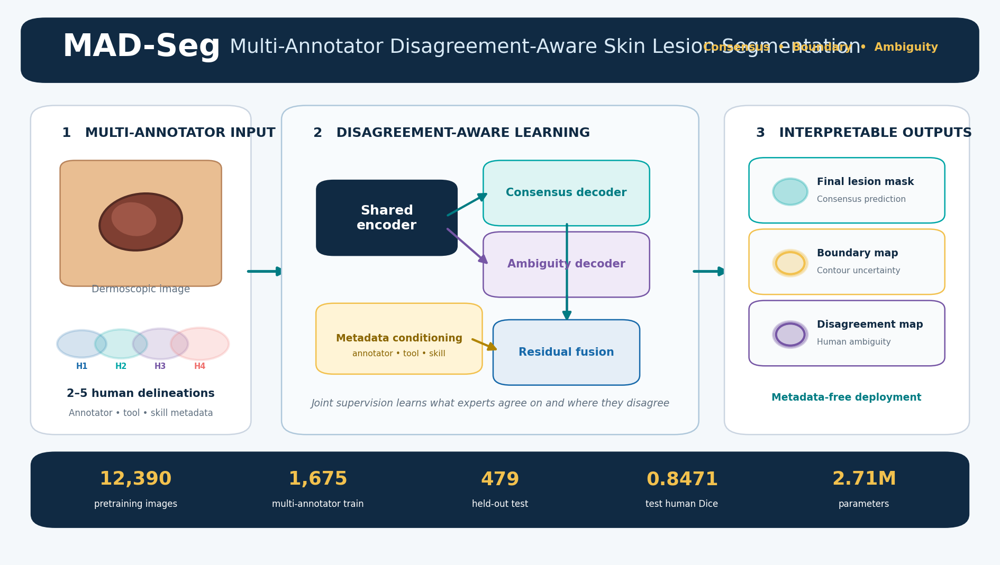

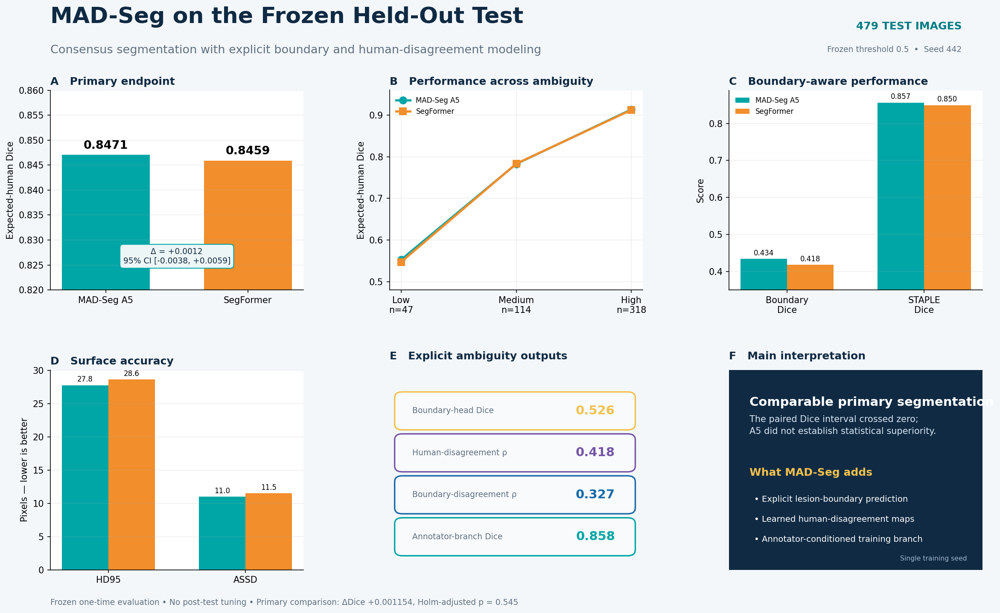


TWO HERO FIGURES CREATED
Graphical abstract PNG: /content/drive/MyDrive/MADSeg/outputs/paper_artifacts/figures/Hero_Graphical_Abstract_MADSeg.png
Graphical abstract SVG: /content/drive/MyDrive/MADSeg/outputs/paper_artifacts/figures/Hero_Graphical_Abstract_MADSeg.svg
Results dashboard PNG: /content/drive/MyDrive/MADSeg/outputs/paper_artifacts/figures/Hero_Frozen_Test_Results_Dashboard.png
Results dashboard SVG: /content/drive/MyDrive/MADSeg/outputs/paper_artifacts/figures/Hero_Frozen_Test_Results_Dashboard.svg
Registry updated: /content/drive/MyDrive/MADSeg/outputs/paper_artifacts/figure_registry.csv

DataLoader access: 0
Model inference: no
Checkpoints modified: no

These are candidate hero figures. After visual review, use them to replace weaker figures rather than increasing the main manuscript beyond 15 figures.


In [ ]:
# ============================================================
# TWO HIGH-IMPACT MAD-SEG HERO FIGURES
#
# 1. Graphical abstract
# 2. Frozen test-results dashboard
#
# Uses saved results only.
# No DataLoader access.
# No model inference.
# ============================================================

import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.patches import (
    FancyBboxPatch,
    FancyArrowPatch,
    Circle,
    Ellipse,
)


# ------------------------------------------------------------
# 1. Paths and frozen results
# ------------------------------------------------------------

PROJECT_ROOT = Path("/content/drive/MyDrive/MADSeg")

TEST_ROOT = (
    PROJECT_ROOT
    / "outputs/final_test_evaluation"
)

FIGURE_ROOT = (
    PROJECT_ROOT
    / "outputs/paper_artifacts/figures"
)

FIGURE_REGISTRY = (
    PROJECT_ROOT
    / "outputs/paper_artifacts/figure_registry.csv"
)

FIGURE_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)

SUMMARY_PATH = (
    TEST_ROOT
    / "A5_SegFormer_test_summary.csv"
)

IAA_PATH = (
    TEST_ROOT
    / "A5_SegFormer_test_by_IAA.csv"
)

PAIRED_PATH = (
    TEST_ROOT
    / "A5_vs_SegFormer_paired_test_comparison.csv"
)

assert SUMMARY_PATH.exists()
assert IAA_PATH.exists()
assert PAIRED_PATH.exists()

summary = pd.read_csv(
    SUMMARY_PATH
).set_index("model")

iaa = pd.read_csv(IAA_PATH)
paired = pd.read_csv(PAIRED_PATH)

primary = paired[
    paired["metric"] == "expected_human_dice"
].iloc[0]

A5_COLOR = "#00A6A6"
A5_DARK = "#007C83"
SEG_COLOR = "#F28E2B"
NAVY = "#102A43"
BLUE = "#1769AA"
GOLD = "#F2C14E"
CORAL = "#EF6F6C"
PURPLE = "#7656A5"
PALE = "#F4F8FB"
GRAY = "#607080"
LIGHT_GRAY = "#D9E2EC"
WHITE = "#FFFFFF"


plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "axes.titleweight": "bold",
})


def rounded_box(
    axis,
    x,
    y,
    width,
    height,
    facecolor,
    edgecolor="none",
    radius=0.025,
    linewidth=1.2,
    alpha=1.0,
):
    patch = FancyBboxPatch(
        (x, y),
        width,
        height,
        boxstyle=(
            f"round,pad=0.012,"
            f"rounding_size={radius}"
        ),
        facecolor=facecolor,
        edgecolor=edgecolor,
        linewidth=linewidth,
        alpha=alpha,
    )

    axis.add_patch(patch)
    return patch


def add_arrow(
    axis,
    start,
    end,
    color=NAVY,
    linewidth=2,
):
    arrow = FancyArrowPatch(
        start,
        end,
        arrowstyle="-|>",
        mutation_scale=16,
        linewidth=linewidth,
        color=color,
        connectionstyle="arc3,rad=0",
    )

    axis.add_patch(arrow)


def add_metric_chip(
    axis,
    x,
    y,
    width,
    title,
    value,
    color,
):
    rounded_box(
        axis,
        x,
        y,
        width,
        0.075,
        WHITE,
        edgecolor=color,
        radius=0.018,
        linewidth=1.5,
    )

    axis.text(
        x + 0.014,
        y + 0.050,
        title,
        fontsize=8,
        color=GRAY,
        va="center",
        fontweight="bold",
    )

    axis.text(
        x + width - 0.014,
        y + 0.030,
        value,
        fontsize=12,
        color=color,
        ha="right",
        va="center",
        fontweight="bold",
    )


# ============================================================
# FIGURE A: GRAPHICAL ABSTRACT
# ============================================================

figure, axis = plt.subplots(
    figsize=(16, 9)
)

figure.patch.set_facecolor(PALE)
axis.set_facecolor(PALE)
axis.set_xlim(0, 1)
axis.set_ylim(0, 1)
axis.axis("off")


# Header
rounded_box(
    axis,
    0.025,
    0.875,
    0.95,
    0.095,
    NAVY,
    radius=0.025,
)

axis.text(
    0.055,
    0.928,
    "MAD-Seg",
    fontsize=28,
    color=WHITE,
    fontweight="bold",
    va="center",
)

axis.text(
    0.225,
    0.928,
    (
        "Multi-Annotator Disagreement-Aware "
        "Skin Lesion Segmentation"
    ),
    fontsize=18,
    color="#D9EAF7",
    va="center",
)

axis.text(
    0.945,
    0.928,
    "Consensus  •  Boundary  •  Ambiguity",
    fontsize=10,
    color=GOLD,
    ha="right",
    va="center",
    fontweight="bold",
)


# ------------------------------------------------------------
# Input card
# ------------------------------------------------------------

rounded_box(
    axis,
    0.035,
    0.235,
    0.20,
    0.575,
    WHITE,
    edgecolor="#CBD5E1",
)

axis.text(
    0.055,
    0.765,
    "1   MULTI-ANNOTATOR INPUT",
    fontsize=12,
    color=NAVY,
    fontweight="bold",
)

# Stylized dermoscopic image
rounded_box(
    axis,
    0.065,
    0.505,
    0.14,
    0.205,
    "#E9BE92",
    edgecolor="#B8845B",
    radius=0.015,
)

axis.add_patch(
    Ellipse(
        (0.135, 0.61),
        0.082,
        0.105,
        angle=-15,
        facecolor="#7F3F32",
        edgecolor="#542B23",
        linewidth=2,
    )
)

axis.add_patch(
    Ellipse(
        (0.128, 0.615),
        0.045,
        0.062,
        angle=10,
        facecolor="#A65D4D",
        edgecolor="none",
        alpha=0.8,
    )
)

axis.text(
    0.135,
    0.482,
    "Dermoscopic image",
    ha="center",
    fontsize=9,
    color=GRAY,
)

# Human masks
mask_centers = [
    (0.075, 0.388),
    (0.115, 0.388),
    (0.155, 0.388),
    (0.195, 0.388),
]

mask_colors = [
    BLUE,
    A5_COLOR,
    PURPLE,
    CORAL,
]

for index, (
    center,
    mask_color,
) in enumerate(zip(mask_centers, mask_colors)):
    axis.add_patch(
        Circle(
            center,
            0.025 + index * 0.0015,
            facecolor=mask_color,
            alpha=0.18,
            edgecolor=mask_color,
            linewidth=2,
        )
    )

    axis.text(
        center[0],
        center[1] - 0.045,
        f"H{index + 1}",
        ha="center",
        fontsize=7,
        color=mask_color,
        fontweight="bold",
    )

axis.text(
    0.135,
    0.292,
    "2–5 human delineations",
    ha="center",
    fontsize=10,
    color=NAVY,
    fontweight="bold",
)

axis.text(
    0.135,
    0.257,
    "Annotator • tool • skill metadata",
    ha="center",
    fontsize=8,
    color=GRAY,
)


# Arrow input to model
add_arrow(
    axis,
    (0.242, 0.52),
    (0.286, 0.52),
    A5_DARK,
    linewidth=2.5,
)


# ------------------------------------------------------------
# Architecture card
# ------------------------------------------------------------

rounded_box(
    axis,
    0.29,
    0.235,
    0.40,
    0.575,
    "#F8FBFD",
    edgecolor="#AFC8DB",
)

axis.text(
    0.31,
    0.765,
    "2   DISAGREEMENT-AWARE LEARNING",
    fontsize=12,
    color=NAVY,
    fontweight="bold",
)

# Encoder
rounded_box(
    axis,
    0.325,
    0.56,
    0.12,
    0.115,
    NAVY,
    radius=0.018,
)

axis.text(
    0.385,
    0.617,
    "Shared\nencoder",
    ha="center",
    va="center",
    fontsize=12,
    color=WHITE,
    fontweight="bold",
)

# Decoders
rounded_box(
    axis,
    0.495,
    0.615,
    0.145,
    0.095,
    "#DDF4F3",
    edgecolor=A5_COLOR,
    radius=0.018,
)

axis.text(
    0.5675,
    0.663,
    "Consensus decoder",
    ha="center",
    va="center",
    fontsize=10,
    color=A5_DARK,
    fontweight="bold",
)

rounded_box(
    axis,
    0.495,
    0.485,
    0.145,
    0.095,
    "#F0EAF8",
    edgecolor=PURPLE,
    radius=0.018,
)

axis.text(
    0.5675,
    0.533,
    "Ambiguity decoder",
    ha="center",
    va="center",
    fontsize=10,
    color=PURPLE,
    fontweight="bold",
)

add_arrow(
    axis,
    (0.445, 0.62),
    (0.49, 0.665),
    A5_DARK,
)

add_arrow(
    axis,
    (0.445, 0.60),
    (0.49, 0.53),
    PURPLE,
)

# Metadata
rounded_box(
    axis,
    0.325,
    0.345,
    0.145,
    0.105,
    "#FFF4D6",
    edgecolor=GOLD,
    radius=0.018,
)

axis.text(
    0.3975,
    0.398,
    "Metadata conditioning",
    ha="center",
    va="center",
    fontsize=9,
    color="#8A6500",
    fontweight="bold",
)

axis.text(
    0.3975,
    0.366,
    "annotator • tool • skill",
    ha="center",
    fontsize=7.5,
    color="#8A6500",
)

# Fusion
rounded_box(
    axis,
    0.505,
    0.325,
    0.125,
    0.095,
    "#E5EEF7",
    edgecolor=BLUE,
    radius=0.018,
)

axis.text(
    0.5675,
    0.373,
    "Residual fusion",
    ha="center",
    va="center",
    fontsize=10,
    color=BLUE,
    fontweight="bold",
)

add_arrow(
    axis,
    (0.47, 0.398),
    (0.50, 0.375),
    "#B18400",
)

add_arrow(
    axis,
    (0.568, 0.48),
    (0.568, 0.425),
    PURPLE,
)

add_arrow(
    axis,
    (0.568, 0.61),
    (0.568, 0.425),
    A5_DARK,
)

axis.text(
    0.49,
    0.275,
    (
        "Joint supervision learns what experts agree on "
        "and where they disagree"
    ),
    ha="center",
    fontsize=9,
    color=GRAY,
    style="italic",
)


# Arrow architecture to outputs
add_arrow(
    axis,
    (0.695, 0.52),
    (0.735, 0.52),
    A5_DARK,
    linewidth=2.5,
)


# ------------------------------------------------------------
# Output card
# ------------------------------------------------------------

rounded_box(
    axis,
    0.74,
    0.235,
    0.225,
    0.575,
    WHITE,
    edgecolor="#CBD5E1",
)

axis.text(
    0.76,
    0.765,
    "3   INTERPRETABLE OUTPUTS",
    fontsize=12,
    color=NAVY,
    fontweight="bold",
)

output_specs = [
    (
        0.665,
        A5_COLOR,
        "Final lesion mask",
        "Consensus prediction",
    ),
    (
        0.535,
        GOLD,
        "Boundary map",
        "Contour uncertainty",
    ),
    (
        0.405,
        PURPLE,
        "Disagreement map",
        "Human ambiguity",
    ),
]

for y, color, title, subtitle in output_specs:
    rounded_box(
        axis,
        0.765,
        y - 0.045,
        0.175,
        0.095,
        "#F9FBFC",
        edgecolor=color,
        radius=0.016,
    )

    axis.add_patch(
        Ellipse(
            (0.795, y),
            0.035,
            0.048,
            facecolor=color,
            edgecolor=color,
            linewidth=2,
            alpha=0.30,
        )
    )

    if title != "Final lesion mask":
        axis.add_patch(
            Ellipse(
                (0.795, y),
                0.029,
                0.040,
                facecolor="none",
                edgecolor=color,
                linewidth=2,
            )
        )

    axis.text(
        0.822,
        y + 0.013,
        title,
        fontsize=9,
        color=NAVY,
        fontweight="bold",
    )

    axis.text(
        0.822,
        y - 0.018,
        subtitle,
        fontsize=7.5,
        color=GRAY,
    )

axis.text(
    0.852,
    0.285,
    "Metadata-free deployment",
    ha="center",
    fontsize=9,
    color=A5_DARK,
    fontweight="bold",
)


# ------------------------------------------------------------
# Evidence ribbon
# ------------------------------------------------------------

rounded_box(
    axis,
    0.035,
    0.065,
    0.93,
    0.115,
    NAVY,
    radius=0.025,
)

evidence_items = [
    ("12,390", "pretraining images"),
    ("1,675", "multi-annotator train"),
    ("479", "held-out test"),
    ("0.8471", "test human Dice"),
    ("2.71M", "parameters"),
]

positions = np.linspace(
    0.13,
    0.87,
    len(evidence_items),
)

for x, (value, label) in zip(
    positions,
    evidence_items,
):
    axis.text(
        x,
        0.132,
        value,
        color=GOLD,
        fontsize=17,
        ha="center",
        fontweight="bold",
    )

    axis.text(
        x,
        0.092,
        label,
        color=WHITE,
        fontsize=8,
        ha="center",
    )

GRAPHICAL_PNG = (
    FIGURE_ROOT
    / "Hero_Graphical_Abstract_MADSeg.png"
)

GRAPHICAL_SVG = (
    FIGURE_ROOT
    / "Hero_Graphical_Abstract_MADSeg.svg"
)

figure.savefig(
    GRAPHICAL_PNG,
    dpi=300,
    bbox_inches="tight",
    facecolor=PALE,
)

figure.savefig(
    GRAPHICAL_SVG,
    bbox_inches="tight",
    facecolor=PALE,
)

plt.show()
plt.close(figure)


# ============================================================
# FIGURE B: FROZEN RESULTS DASHBOARD
# ============================================================

figure = plt.figure(
    figsize=(16, 10),
    facecolor="#F3F7FA",
)

grid = figure.add_gridspec(
    2,
    3,
    left=0.055,
    right=0.965,
    bottom=0.08,
    top=0.83,
    wspace=0.34,
    hspace=0.40,
)

figure.text(
    0.055,
    0.935,
    "MAD-Seg on the Frozen Held-Out Test",
    fontsize=25,
    color=NAVY,
    fontweight="bold",
)

figure.text(
    0.055,
    0.888,
    (
        "Consensus segmentation with explicit boundary "
        "and human-disagreement modeling"
    ),
    fontsize=13,
    color=GRAY,
)

figure.text(
    0.945,
    0.925,
    "479 TEST IMAGES",
    ha="right",
    fontsize=12,
    color=A5_DARK,
    fontweight="bold",
)

figure.text(
    0.945,
    0.890,
    "Frozen threshold 0.5  •  Seed 442",
    ha="right",
    fontsize=9,
    color=GRAY,
)


# Panel A: primary Dice
axis = figure.add_subplot(grid[0, 0])
axis.set_facecolor(WHITE)

dice_values = [
    summary.loc["A5", "expected_human_dice"],
    summary.loc[
        "SegFormer",
        "expected_human_dice",
    ],
]

bars = axis.bar(
    ["MAD-Seg A5", "SegFormer"],
    dice_values,
    color=[A5_COLOR, SEG_COLOR],
    width=0.62,
)

axis.bar_label(
    bars,
    labels=[
        f"{value:.4f}"
        for value in dice_values
    ],
    fontsize=13,
    padding=4,
    fontweight="bold",
)

axis.set_ylim(0.82, 0.86)
axis.set_ylabel("Expected-human Dice")
axis.set_title(
    "A   Primary endpoint",
    loc="left",
    color=NAVY,
)
axis.grid(axis="y", alpha=0.20)
axis.spines[["top", "right"]].set_visible(False)

axis.text(
    0.5,
    0.825,
    (
        f"Δ = {primary['raw_delta_a5_minus_segformer']:+.4f}\n"
        f"95% CI [{primary['improvement_ci95_lower']:+.4f}, "
        f"{primary['improvement_ci95_upper']:+.4f}]"
    ),
    ha="center",
    va="bottom",
    fontsize=9,
    color=NAVY,
    bbox={
        "boxstyle": "round,pad=0.4",
        "facecolor": "#EDF6F7",
        "edgecolor": A5_COLOR,
    },
)


# Panel B: IAA
axis = figure.add_subplot(grid[0, 1])
axis.set_facecolor(WHITE)

iaa_order = ["low", "medium", "high"]
x = np.arange(3)

for model_name, color, marker in [
    ("A5", A5_COLOR, "o"),
    ("SegFormer", SEG_COLOR, "s"),
]:
    model_data = (
        iaa[
            iaa["model"] == model_name
        ]
        .set_index("iaa_group")
        .reindex(iaa_order)
    )

    axis.plot(
        x,
        model_data["expected_human_dice"],
        marker=marker,
        markersize=8,
        linewidth=2.5,
        color=color,
        label=(
            "MAD-Seg A5"
            if model_name == "A5"
            else model_name
        ),
    )

axis.set_xticks(x)
axis.set_xticklabels([
    "Low\nn=47",
    "Medium\nn=114",
    "High\nn=318",
])
axis.set_ylim(0.48, 0.96)
axis.set_ylabel("Expected-human Dice")
axis.set_title(
    "B   Performance across ambiguity",
    loc="left",
    color=NAVY,
)
axis.legend(frameon=False, fontsize=8)
axis.grid(alpha=0.20)
axis.spines[["top", "right"]].set_visible(False)


# Panel C: boundary and STAPLE
axis = figure.add_subplot(grid[0, 2])
axis.set_facecolor(WHITE)

metrics = [
    (
        "expected_human_boundary_dice",
        "Boundary\nDice",
    ),
    (
        "staple_dice",
        "STAPLE\nDice",
    ),
]

x = np.arange(len(metrics))
width = 0.34

for offset, model_name, color in [
    (-width / 2, "A5", A5_COLOR),
    (width / 2, "SegFormer", SEG_COLOR),
]:
    values = [
        summary.loc[model_name, metric]
        for metric, _ in metrics
    ]

    bars = axis.bar(
        x + offset,
        values,
        width,
        color=color,
        label=(
            "MAD-Seg A5"
            if model_name == "A5"
            else model_name
        ),
    )

    axis.bar_label(
        bars,
        fmt="%.3f",
        fontsize=8,
        padding=2,
    )

axis.set_xticks(x)
axis.set_xticklabels(
    [label for _, label in metrics]
)
axis.set_ylim(0.35, 0.89)
axis.set_ylabel("Score")
axis.set_title(
    "C   Boundary-aware performance",
    loc="left",
    color=NAVY,
)
axis.legend(frameon=False, fontsize=8)
axis.grid(axis="y", alpha=0.20)
axis.spines[["top", "right"]].set_visible(False)


# Panel D: surface distances
axis = figure.add_subplot(grid[1, 0])
axis.set_facecolor(WHITE)

surface_metrics = [
    ("expected_human_hd95_px", "HD95"),
    ("expected_human_assd_px", "ASSD"),
]

x = np.arange(2)

for offset, model_name, color in [
    (-width / 2, "A5", A5_COLOR),
    (width / 2, "SegFormer", SEG_COLOR),
]:
    values = [
        summary.loc[model_name, metric]
        for metric, _ in surface_metrics
    ]

    bars = axis.bar(
        x + offset,
        values,
        width,
        color=color,
    )

    axis.bar_label(
        bars,
        fmt="%.1f",
        fontsize=8,
        padding=2,
    )

axis.set_xticks(x)
axis.set_xticklabels([
    "HD95",
    "ASSD",
])
axis.set_ylabel("Pixels — lower is better")
axis.set_title(
    "D   Surface accuracy",
    loc="left",
    color=NAVY,
)
axis.grid(axis="y", alpha=0.20)
axis.spines[["top", "right"]].set_visible(False)


# Panel E: unique outputs
axis = figure.add_subplot(grid[1, 1])
axis.set_facecolor(WHITE)
axis.axis("off")

axis.set_title(
    "E   Explicit ambiguity outputs",
    loc="left",
    color=NAVY,
    pad=12,
)

unique_metrics = [
    (
        "Boundary-head Dice",
        summary.loc["A5", "boundary_head_dice"],
        GOLD,
    ),
    (
        "Human-disagreement ρ",
        summary.loc[
            "A5",
            "learned_human_disagreement_spearman",
        ],
        PURPLE,
    ),
    (
        "Boundary-disagreement ρ",
        summary.loc[
            "A5",
            "learned_boundary_disagreement_spearman",
        ],
        BLUE,
    ),
    (
        "Annotator-branch Dice",
        summary.loc[
            "A5",
            "annotator_branch_dice",
        ],
        A5_COLOR,
    ),
]

for index, (
    metric_label,
    metric_value,
    color,
) in enumerate(unique_metrics):
    y = 0.83 - index * 0.21

    box = FancyBboxPatch(
        (0.04, y - 0.11),
        0.91,
        0.15,
        boxstyle=(
            "round,pad=0.02,"
            "rounding_size=0.03"
        ),
        facecolor="#F8FAFC",
        edgecolor=color,
        linewidth=1.6,
        transform=axis.transAxes,
    )

    axis.add_patch(box)

    axis.text(
        0.09,
        y - 0.035,
        metric_label,
        transform=axis.transAxes,
        fontsize=9,
        color=GRAY,
        va="center",
    )

    axis.text(
        0.89,
        y - 0.035,
        f"{metric_value:.3f}",
        transform=axis.transAxes,
        fontsize=14,
        color=color,
        fontweight="bold",
        ha="right",
        va="center",
    )


# Panel F: interpretation
axis = figure.add_subplot(grid[1, 2])
axis.set_facecolor(NAVY)
axis.axis("off")

axis.set_title(
    "F   Main interpretation",
    loc="left",
    color=NAVY,
    pad=12,
)

background = FancyBboxPatch(
    (0, 0),
    1,
    1,
    boxstyle=(
        "round,pad=0.025,"
        "rounding_size=0.04"
    ),
    facecolor=NAVY,
    edgecolor=NAVY,
    transform=axis.transAxes,
)

axis.add_patch(background)

axis.text(
    0.08,
    0.82,
    "Comparable primary segmentation",
    transform=axis.transAxes,
    color=WHITE,
    fontsize=14,
    fontweight="bold",
)

axis.text(
    0.08,
    0.68,
    (
        "The paired Dice interval crossed zero;\n"
        "A5 did not establish statistical superiority."
    ),
    transform=axis.transAxes,
    color="#D7E6F2",
    fontsize=10,
    linespacing=1.5,
)

axis.text(
    0.08,
    0.47,
    "What MAD-Seg adds",
    transform=axis.transAxes,
    color=GOLD,
    fontsize=12,
    fontweight="bold",
)

axis.text(
    0.10,
    0.34,
    "• Explicit lesion-boundary prediction",
    transform=axis.transAxes,
    color=WHITE,
    fontsize=9.5,
)

axis.text(
    0.10,
    0.24,
    "• Learned human-disagreement maps",
    transform=axis.transAxes,
    color=WHITE,
    fontsize=9.5,
)

axis.text(
    0.10,
    0.14,
    "• Annotator-conditioned training branch",
    transform=axis.transAxes,
    color=WHITE,
    fontsize=9.5,
)

axis.text(
    0.94,
    0.045,
    "Single training seed",
    transform=axis.transAxes,
    color="#9FB3C8",
    fontsize=7.5,
    ha="right",
)


# Footer
figure.text(
    0.055,
    0.025,
    (
        "Frozen one-time evaluation • No post-test tuning • "
        "Primary comparison: ΔDice +0.001154, "
        "Holm-adjusted p = 0.545"
    ),
    fontsize=9,
    color=GRAY,
)

RESULTS_PNG = (
    FIGURE_ROOT
    / "Hero_Frozen_Test_Results_Dashboard.png"
)

RESULTS_SVG = (
    FIGURE_ROOT
    / "Hero_Frozen_Test_Results_Dashboard.svg"
)

figure.savefig(
    RESULTS_PNG,
    dpi=300,
    bbox_inches="tight",
    facecolor="#F3F7FA",
)

figure.savefig(
    RESULTS_SVG,
    bbox_inches="tight",
    facecolor="#F3F7FA",
)

plt.show()
plt.close(figure)


# ------------------------------------------------------------
# 3. Register as candidate hero figures
# ------------------------------------------------------------

hero_rows = [
    {
        "figure_id":
            "Hero_Graphical_Abstract",
        "figure_number": "",
        "short_name":
            "MAD-Seg Graphical Abstract",
        "filename": GRAPHICAL_PNG.name,
        "source_file":
            "Frozen project design and results",
        "split": "conceptual/mixed",
        "selection_rule":
            "Designed after experiment closure",
        "caption_draft": (
            "Graphical overview of the MAD-Seg "
            "multi-annotator disagreement-aware "
            "segmentation framework."
        ),
        "manuscript_section":
            "Graphical abstract",
        "status": "candidate",
        "notes": (
            "Conceptual architecture illustration; "
            "numerical ribbon uses frozen results."
        ),
    },
    {
        "figure_id":
            "Hero_Frozen_Results",
        "figure_number": "",
        "short_name":
            "Frozen Test Results Dashboard",
        "filename": RESULTS_PNG.name,
        "source_file": str(TEST_ROOT),
        "split": "test",
        "selection_rule":
            "Frozen one-time held-out-test results",
        "caption_draft": (
            "Summary of frozen held-out-test "
            "performance, subgroup behavior, surface "
            "accuracy, and MAD-Seg auxiliary outputs."
        ),
        "manuscript_section":
            "Results summary",
        "status": "candidate",
        "notes": (
            "Primary difference is not statistically "
            "significant; figure states this explicitly."
        ),
    },
]

if FIGURE_REGISTRY.exists():
    registry = pd.read_csv(
        FIGURE_REGISTRY
    )
else:
    registry = pd.DataFrame(
        hero_rows
    ).iloc[0:0]

aliases = {
    "figure_id": "figure_id",
    "id": "figure_id",
    "number": "figure_number",
    "figure_number": "figure_number",
    "short_name": "short_name",
    "filename": "filename",
    "file_name": "filename",
    "source_file": "source_file",
    "source": "source_file",
    "source_data": "source_file",
    "split": "split",
    "data_split": "split",
    "selection_rule": "selection_rule",
    "caption": "caption_draft",
    "caption_draft": "caption_draft",
    "section": "manuscript_section",
    "manuscript_section": "manuscript_section",
    "status": "status",
    "notes": "notes",
}

identifier_column = next(
    (
        column
        for column in [
            "figure_id",
            "id",
            "filename",
        ]
        if column in registry.columns
    ),
    registry.columns[0],
)

converted_rows = []

for hero_row in hero_rows:
    converted = {}

    for column in registry.columns:
        source_column = aliases.get(
            column,
            column,
        )

        converted[column] = hero_row.get(
            source_column,
            "",
        )

    converted_rows.append(converted)

converted_frame = pd.DataFrame(
    converted_rows,
    columns=registry.columns,
)

incoming_ids = set(
    converted_frame[
        identifier_column
    ].astype(str)
)

registry = registry[
    ~registry[
        identifier_column
    ].astype(str).isin(incoming_ids)
]

registry = pd.concat(
    [
        registry,
        converted_frame,
    ],
    ignore_index=True,
)

temporary_registry = (
    FIGURE_REGISTRY.with_suffix(
        ".temporary.csv"
    )
)

registry.to_csv(
    temporary_registry,
    index=False,
)

os.replace(
    temporary_registry,
    FIGURE_REGISTRY,
)


print()
print("=" * 70)
print("TWO HERO FIGURES CREATED")
print("=" * 70)
print("Graphical abstract PNG:", GRAPHICAL_PNG)
print("Graphical abstract SVG:", GRAPHICAL_SVG)
print("Results dashboard PNG:", RESULTS_PNG)
print("Results dashboard SVG:", RESULTS_SVG)
print("Registry updated:", FIGURE_REGISTRY)
print()
print("DataLoader access: 0")
print("Model inference: no")
print("Checkpoints modified: no")
print()
print(
    "These are candidate hero figures. After visual "
    "review, use them to replace weaker figures rather "
    "than increasing the main manuscript beyond 15 figures."
)

In [ ]:
from pathlib import Path
import numpy as np

XAI_ROOT = Path(
    "/content/drive/MyDrive/MADSeg/outputs/xai"
)

npz_files = sorted(XAI_ROOT.rglob("*.npz"))

print("NPZ files found:", len(npz_files))

for path in npz_files[:3]:
    print("\nFILE:", path)

    with np.load(path, allow_pickle=True) as data:
        print("Keys:")

        for key in data.files:
            value = data[key]

            print(
                f"  {key:35s}",
                f"shape={value.shape}",
                f"dtype={value.dtype}",
            )

NPZ files found: 24

FILE: /content/drive/MyDrive/MADSeg/outputs/xai/raw_attributions/ISIC_0000401.npz
Keys:
  normalized_image                    shape=(1, 3, 352, 352) dtype=float32
  hard_consensus                      shape=(1, 1, 352, 352) dtype=bool
  human_disagreement                  shape=(1, 1, 352, 352) dtype=float32
  consensus_boundary                  shape=(1, 1, 352, 352) dtype=float32
  boundary_disagreement               shape=(1, 1, 352, 352) dtype=float32
  a5_final_probability                shape=(1, 1, 352, 352) dtype=float32
  a5_boundary_probability             shape=(1, 1, 352, 352) dtype=float32
  a5_disagreement_probability         shape=(1, 1, 352, 352) dtype=float32
  segformer_probability               shape=(1, 1, 352, 352) dtype=float32
  A5_final_mask_ig                    shape=(1, 1, 352, 352) dtype=float32
  A5_final_mask_occlusion             shape=(1, 1, 352, 352) dtype=float32
  A5_boundary_ig                      shape=(1, 1, 352, 352) dtype=fl

Metadata source: /content/drive/MyDrive/MADSeg/outputs/xai/xai_validation_case_manifest.csv

Selected frozen validation cases:


,isic_id,iaa_group,selection_role,a5_consensus_dice,segformer_consensus_dice,disagreement_correlation
8,ISIC_0012806,low,Representative low-IAA case,0.452782,0.512780,0.534914
3,ISIC_0003231,medium,Representative medium-IAA case,0.817281,0.836576,0.187015
6,ISIC_0011321,high,Representative high-IAA case,0.937065,0.946492,0.563451
10,ISIC_0014187,low,Lowest A5 consensus Dice among remaining froze...,0.116345,0.050202,0.489081


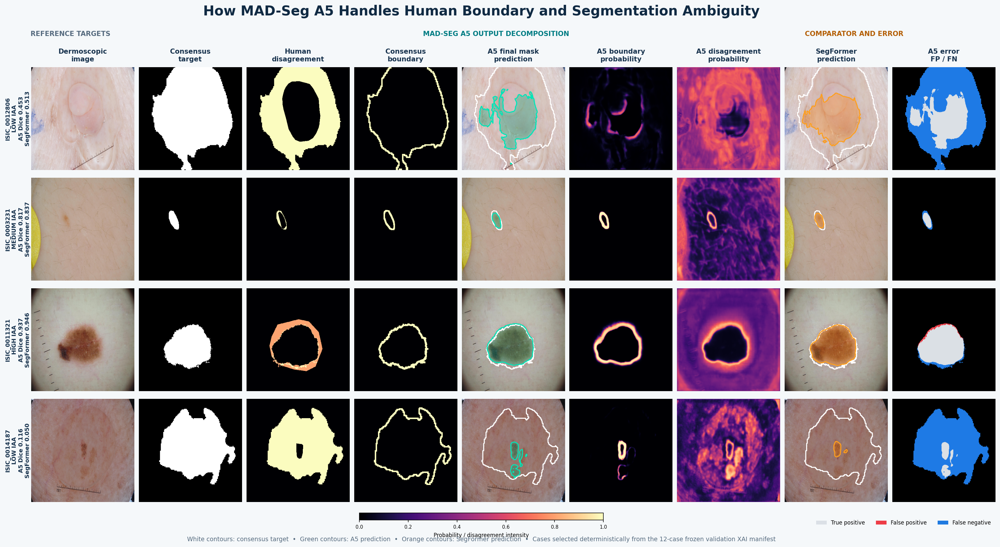


A5 QUALITATIVE EVALUATION DIAGRAM CREATED
PNG: /content/drive/MyDrive/MADSeg/outputs/paper_artifacts/figures/Hero_A5_Qualitative_Evaluation.png
Editable SVG: /content/drive/MyDrive/MADSeg/outputs/paper_artifacts/figures/Hero_A5_Qualitative_Evaluation.svg
Selected cases: /content/drive/MyDrive/MADSeg/outputs/paper_artifacts/tables/A5_Qualitative_Evaluation_Cases.csv
Registry: /content/drive/MyDrive/MADSeg/outputs/paper_artifacts/figure_registry.csv
DataLoader access: 0
Model inference: no

This is a candidate replacement for one of the weaker ordinary charts, not an additional required main-paper figure.


In [ ]:
# ============================================================
# A5 QUALITATIVE EVALUATION DIAGRAM
#
# Uses only frozen validation NPZ artifacts.
# No inference and no dataset access.
# ============================================================

import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch


PROJECT_ROOT = Path("/content/drive/MyDrive/MADSeg")

XAI_ROOT = PROJECT_ROOT / "outputs/xai"

RAW_ROOT = XAI_ROOT / "raw_attributions"

FIGURE_ROOT = (
    PROJECT_ROOT
    / "outputs/paper_artifacts/figures"
)

TABLE_ROOT = (
    PROJECT_ROOT
    / "outputs/paper_artifacts/tables"
)

FIGURE_REGISTRY = (
    PROJECT_ROOT
    / "outputs/paper_artifacts/figure_registry.csv"
)

FIGURE_ROOT.mkdir(parents=True, exist_ok=True)
TABLE_ROOT.mkdir(parents=True, exist_ok=True)

OUTPUT_PNG = (
    FIGURE_ROOT
    / "Hero_A5_Qualitative_Evaluation.png"
)

OUTPUT_SVG = (
    FIGURE_ROOT
    / "Hero_A5_Qualitative_Evaluation.svg"
)

CASE_TABLE = (
    TABLE_ROOT
    / "A5_Qualitative_Evaluation_Cases.csv"
)

THRESHOLD = 0.5

npz_files = sorted(RAW_ROOT.glob("*.npz"))

assert len(npz_files) >= 12, (
    f"Expected at least 12 frozen NPZ files; "
    f"found {len(npz_files)}."
)


# ------------------------------------------------------------
# 1. Find the frozen XAI case metadata
# ------------------------------------------------------------

metadata_candidates = []

search_roots = [
    XAI_ROOT,
    (
        PROJECT_ROOT
        / "outputs/final_experiment_freeze"
    ),
    (
        PROJECT_ROOT
        / "outputs/paper_artifacts/tables"
    ),
]

available_ids = {
    path.stem for path in npz_files
}

for search_root in search_roots:
    if not search_root.exists():
        continue

    for csv_path in search_root.rglob("*.csv"):
        try:
            frame = pd.read_csv(csv_path)
        except Exception:
            continue

        id_column = next(
            (
                column
                for column in [
                    "isic_id",
                    "ISIC_id",
                    "image_id",
                ]
                if column in frame.columns
            ),
            None,
        )

        if id_column is None:
            continue

        matched_ids = set(
            frame[id_column]
            .astype(str)
        ) & available_ids

        if len(matched_ids) == 0:
            continue

        group_column = next(
            (
                column
                for column in [
                    "iaa_group",
                    "IAA_group",
                    "agreement_group",
                ]
                if column in frame.columns
            ),
            None,
        )

        score = len(matched_ids)

        if group_column is not None:
            score += 100

        if "manifest" in csv_path.name.lower():
            score += 50

        metadata_candidates.append({
            "score": score,
            "path": csv_path,
            "frame": frame,
            "id_column": id_column,
            "group_column": group_column,
        })

metadata_candidates.sort(
    key=lambda item: item["score"],
    reverse=True,
)

if metadata_candidates:
    metadata_source = metadata_candidates[0]

    metadata = metadata_source[
        "frame"
    ].copy()

    metadata = metadata.rename(
        columns={
            metadata_source["id_column"]:
                "isic_id",
        }
    )

    if metadata_source["group_column"]:
        metadata = metadata.rename(
            columns={
                metadata_source["group_column"]:
                    "iaa_group",
            }
        )

    metadata["isic_id"] = (
        metadata["isic_id"].astype(str)
    )

    metadata = metadata[
        metadata["isic_id"].isin(
            available_ids
        )
    ].drop_duplicates("isic_id")

    print(
        "Metadata source:",
        metadata_source["path"],
    )
else:
    metadata = pd.DataFrame({
        "isic_id": sorted(available_ids),
        "iaa_group": "unknown",
    })

    print(
        "IAA metadata not found; using unknown groups."
    )

if "iaa_group" not in metadata.columns:
    metadata["iaa_group"] = "unknown"

metadata["iaa_group"] = (
    metadata["iaa_group"]
    .astype(str)
    .str.lower()
)


# ------------------------------------------------------------
# 2. Load frozen arrays and calculate descriptive metrics
# ------------------------------------------------------------

case_records = []


def extract_map(npz_data, key):
    value = np.asarray(
        npz_data[key]
    )

    while value.ndim > 2:
        value = value[0]

    return value.astype(np.float32)


def binary_dice(prediction, target):
    prediction = prediction.astype(bool)
    target = target.astype(bool)

    intersection = np.logical_and(
        prediction,
        target,
    ).sum(dtype=np.float64)

    denominator = (
        prediction.sum(dtype=np.float64)
        + target.sum(dtype=np.float64)
    )

    if denominator == 0:
        return 1.0

    return float(
        2.0 * intersection / denominator
    )


def safe_correlation(first, second):
    first = first.reshape(-1)
    second = second.reshape(-1)

    if (
        np.std(first) < 1e-8
        or np.std(second) < 1e-8
    ):
        return np.nan

    return float(
        np.corrcoef(first, second)[0, 1]
    )


for npz_path in npz_files:
    isic_id = npz_path.stem

    with np.load(
        npz_path,
        allow_pickle=True,
    ) as data:
        hard_consensus = (
            extract_map(
                data,
                "hard_consensus",
            ) >= THRESHOLD
        )

        a5_probability = extract_map(
            data,
            "a5_final_probability",
        )

        segformer_probability = extract_map(
            data,
            "segformer_probability",
        )

        human_disagreement = extract_map(
            data,
            "human_disagreement",
        )

        a5_disagreement = extract_map(
            data,
            "a5_disagreement_probability",
        )

    metadata_match = metadata[
        metadata["isic_id"] == isic_id
    ]

    iaa_group = (
        metadata_match["iaa_group"].iloc[0]
        if len(metadata_match)
        else "unknown"
    )

    case_records.append({
        "isic_id": isic_id,
        "iaa_group": iaa_group,
        "npz_path": str(npz_path),
        "a5_consensus_dice": binary_dice(
            a5_probability >= THRESHOLD,
            hard_consensus,
        ),
        "segformer_consensus_dice":
            binary_dice(
                segformer_probability >= THRESHOLD,
                hard_consensus,
            ),
        "disagreement_correlation":
            safe_correlation(
                a5_disagreement,
                human_disagreement,
            ),
    })

case_frame = pd.DataFrame(case_records)


# ------------------------------------------------------------
# 3. Deterministic transparent case selection
# ------------------------------------------------------------

selected_rows = []
selected_ids = set()

for group in [
    "low",
    "medium",
    "high",
]:
    group_frame = case_frame[
        case_frame["iaa_group"] == group
    ].copy()

    if len(group_frame) == 0:
        continue

    group_median = group_frame[
        "a5_consensus_dice"
    ].median()

    group_frame[
        "distance_from_group_median"
    ] = np.abs(
        group_frame["a5_consensus_dice"]
        - group_median
    )

    representative = group_frame.sort_values(
        [
            "distance_from_group_median",
            "isic_id",
        ]
    ).iloc[0].copy()

    representative["selection_role"] = (
        f"Representative {group}-IAA case"
    )

    selected_rows.append(representative)
    selected_ids.add(
        representative["isic_id"]
    )

# Fourth row: worst remaining A5 case.
remaining = case_frame[
    ~case_frame["isic_id"].isin(
        selected_ids
    )
].copy()

if len(remaining):
    failure_case = remaining.sort_values(
        [
            "a5_consensus_dice",
            "isic_id",
        ],
        ascending=[True, True],
    ).iloc[0].copy()

    failure_case["selection_role"] = (
        "Lowest A5 consensus Dice among remaining "
        "frozen XAI cases"
    )

    selected_rows.append(failure_case)

selected_cases = pd.DataFrame(
    selected_rows
)

# Fallback to exactly four deterministic cases.
if len(selected_cases) < 4:
    missing_count = 4 - len(selected_cases)

    additional = (
        case_frame[
            ~case_frame["isic_id"].isin(
                selected_cases["isic_id"]
            )
        ]
        .sort_values("isic_id")
        .head(missing_count)
        .copy()
    )

    additional["selection_role"] = (
        "Deterministic frozen-case fallback"
    )

    selected_cases = pd.concat(
        [
            selected_cases,
            additional,
        ],
        ignore_index=True,
    )

selected_cases = selected_cases.head(4)

assert len(selected_cases) == 4
assert selected_cases["isic_id"].nunique() == 4

selected_cases.to_csv(
    CASE_TABLE,
    index=False,
)

print()
print("Selected frozen validation cases:")

display(
    selected_cases[[
        "isic_id",
        "iaa_group",
        "selection_role",
        "a5_consensus_dice",
        "segformer_consensus_dice",
        "disagreement_correlation",
    ]]
)


# ------------------------------------------------------------
# 4. Display helpers
# ------------------------------------------------------------

IMAGENET_MEAN = np.array(
    [0.485, 0.456, 0.406],
    dtype=np.float32,
).reshape(3, 1, 1)

IMAGENET_STD = np.array(
    [0.229, 0.224, 0.225],
    dtype=np.float32,
).reshape(3, 1, 1)


def recover_rgb(normalized_image):
    image = np.asarray(
        normalized_image,
        dtype=np.float32,
    )

    while image.ndim > 3:
        image = image[0]

    if image.shape[0] == 3:
        image = (
            image * IMAGENET_STD
            + IMAGENET_MEAN
        )

        image = np.transpose(
            image,
            (1, 2, 0),
        )

    return np.clip(image, 0.0, 1.0)


def add_contour(
    axis,
    mask,
    color,
    linewidth=1.5,
    linestyle="-",
):
    if (
        np.asarray(mask).max()
        == np.asarray(mask).min()
    ):
        return

    axis.contour(
        mask.astype(float),
        levels=[0.5],
        colors=[color],
        linewidths=linewidth,
        linestyles=linestyle,
    )


def overlay_prediction(
    rgb,
    prediction,
    consensus,
    prediction_color,
):
    overlay = rgb.copy()

    color = np.array(
        prediction_color,
        dtype=np.float32,
    )

    alpha = 0.32

    overlay[prediction] = (
        (1.0 - alpha)
        * overlay[prediction]
        + alpha * color
    )

    return np.clip(overlay, 0, 1)


def make_error_map(
    prediction,
    target,
):
    prediction = prediction.astype(bool)
    target = target.astype(bool)

    true_positive = (
        prediction & target
    )

    false_positive = (
        prediction & ~target
    )

    false_negative = (
        ~prediction & target
    )

    error_image = np.zeros(
        (*prediction.shape, 3),
        dtype=np.float32,
    )

    # Correct lesion: light gray
    error_image[true_positive] = [
        0.86,
        0.88,
        0.90,
    ]

    # False positive: coral red
    error_image[false_positive] = [
        0.93,
        0.24,
        0.28,
    ]

    # False negative: blue
    error_image[false_negative] = [
        0.12,
        0.48,
        0.90,
    ]

    return error_image


# ------------------------------------------------------------
# 5. Build the qualitative evaluation matrix
# ------------------------------------------------------------

column_titles = [
    "Dermoscopic\nimage",
    "Consensus\ntarget",
    "Human\ndisagreement",
    "Consensus\nboundary",
    "A5 final mask\nprediction",
    "A5 boundary\nprobability",
    "A5 disagreement\nprobability",
    "SegFormer\nprediction",
    "A5 error\nFP / FN",
]

number_of_rows = len(selected_cases)
number_of_columns = len(column_titles)

figure, axes = plt.subplots(
    number_of_rows,
    number_of_columns,
    figsize=(22, 10.8),
    constrained_layout=False,
)

figure.patch.set_facecolor("#F5F8FA")

probability_artist = None

for row_index, (_, case) in enumerate(
    selected_cases.iterrows()
):
    npz_path = Path(case["npz_path"])

    with np.load(
        npz_path,
        allow_pickle=True,
    ) as data:
        rgb = recover_rgb(
            data["normalized_image"]
        )

        consensus = (
            extract_map(
                data,
                "hard_consensus",
            ) >= THRESHOLD
        )

        human_disagreement = extract_map(
            data,
            "human_disagreement",
        )

        consensus_boundary = extract_map(
            data,
            "consensus_boundary",
        )

        a5_probability = extract_map(
            data,
            "a5_final_probability",
        )

        a5_boundary = extract_map(
            data,
            "a5_boundary_probability",
        )

        a5_disagreement = extract_map(
            data,
            "a5_disagreement_probability",
        )

        segformer_probability = extract_map(
            data,
            "segformer_probability",
        )

    a5_mask = (
        a5_probability >= THRESHOLD
    )

    segformer_mask = (
        segformer_probability >= THRESHOLD
    )

    a5_overlay = overlay_prediction(
        rgb,
        a5_mask,
        consensus,
        [0.00, 0.72, 0.55],
    )

    segformer_overlay = overlay_prediction(
        rgb,
        segformer_mask,
        consensus,
        [1.00, 0.55, 0.10],
    )

    error_map = make_error_map(
        a5_mask,
        consensus,
    )

    panels = [
        ("rgb", rgb),
        ("binary", consensus),
        ("probability", human_disagreement),
        ("probability", consensus_boundary),
        ("a5_overlay", a5_overlay),
        ("probability", a5_boundary),
        ("probability", a5_disagreement),
        ("seg_overlay", segformer_overlay),
        ("rgb", error_map),
    ]

    for column_index, (
        panel_type,
        panel,
    ) in enumerate(panels):
        axis = axes[
            row_index,
            column_index,
        ]

        axis.set_facecolor("black")
        axis.set_xticks([])
        axis.set_yticks([])

        for spine in axis.spines.values():
            spine.set_visible(False)

        if panel_type in {
            "rgb",
            "a5_overlay",
            "seg_overlay",
        }:
            axis.imshow(panel)

        elif panel_type == "binary":
            axis.imshow(
                panel,
                cmap="gray",
                vmin=0,
                vmax=1,
            )

        else:
            probability_artist = axis.imshow(
                panel,
                cmap="magma",
                vmin=0,
                vmax=1,
            )

        if panel_type == "a5_overlay":
            add_contour(
                axis,
                consensus,
                "white",
                linewidth=1.5,
            )

            add_contour(
                axis,
                a5_mask,
                "#00E6B8",
                linewidth=1.4,
            )

        if panel_type == "seg_overlay":
            add_contour(
                axis,
                consensus,
                "white",
                linewidth=1.5,
            )

            add_contour(
                axis,
                segformer_mask,
                "#FF9F1C",
                linewidth=1.4,
            )

        if row_index == 0:
            axis.set_title(
                column_titles[column_index],
                fontsize=10,
                fontweight="bold",
                color="#17324D",
                pad=9,
            )

    role = str(case["selection_role"])

    axes[row_index, 0].text(
        -0.13,
        0.5,
        (
            f"{case['isic_id']}\n"
            f"{str(case['iaa_group']).upper()} IAA\n"
            f"A5 Dice {case['a5_consensus_dice']:.3f}\n"
            f"SegFormer {case['segformer_consensus_dice']:.3f}"
        ),
        transform=axes[
            row_index,
            0,
        ].transAxes,
        rotation=90,
        va="center",
        ha="center",
        fontsize=8.5,
        color="#17324D",
        fontweight="bold",
    )


# Group separators
figure.text(
    0.075,
    0.985,
    "REFERENCE TARGETS",
    fontsize=10,
    color="#566B7F",
    fontweight="bold",
)

figure.text(
    0.445,
    0.985,
    "MAD-SEG A5 OUTPUT DECOMPOSITION",
    fontsize=10,
    color="#007C83",
    fontweight="bold",
)

figure.text(
    0.805,
    0.985,
    "COMPARATOR AND ERROR",
    fontsize=10,
    color="#B45F06",
    fontweight="bold",
)

figure.suptitle(
    (
        "How MAD-Seg A5 Handles Human Boundary "
        "and Segmentation Ambiguity"
    ),
    fontsize=20,
    fontweight="bold",
    color="#102A43",
    y=1.045,
)

figure.text(
    0.5,
    0.015,
    (
        "White contours: consensus target  •  "
        "Green contours: A5 prediction  •  "
        "Orange contours: SegFormer prediction  •  "
        "Cases selected deterministically from the "
        "12-case frozen validation XAI manifest"
    ),
    ha="center",
    fontsize=9,
    color="#566B7F",
)

# Probability colorbar
colorbar_axis = figure.add_axes([
    0.385,
    0.055,
    0.23,
    0.014,
])

colorbar = figure.colorbar(
    probability_artist,
    cax=colorbar_axis,
    orientation="horizontal",
)

colorbar.set_label(
    "Probability / disagreement intensity",
    fontsize=8,
)

colorbar.ax.tick_params(
    labelsize=7,
)

# Error legend
error_legend = [
    Patch(
        facecolor="#DBE0E6",
        label="True positive",
    ),
    Patch(
        facecolor="#ED3D47",
        label="False positive",
    ),
    Patch(
        facecolor="#1F7AE0",
        label="False negative",
    ),
]

figure.legend(
    handles=error_legend,
    loc="lower right",
    bbox_to_anchor=(0.985, 0.035),
    ncol=3,
    frameon=False,
    fontsize=8,
)

figure.subplots_adjust(
    left=0.075,
    right=0.985,
    top=0.925,
    bottom=0.09,
    wspace=0.035,
    hspace=0.075,
)

figure.savefig(
    OUTPUT_PNG,
    dpi=300,
    bbox_inches="tight",
    facecolor="#F5F8FA",
)

figure.savefig(
    OUTPUT_SVG,
    bbox_inches="tight",
    facecolor="#F5F8FA",
)

plt.show()
plt.close(figure)


# ------------------------------------------------------------
# 6. Register the diagram as a candidate replacement
# ------------------------------------------------------------

registry_row = {
    "figure_id":
        "Hero_A5_Qualitative_Evaluation",
    "figure_number": "",
    "short_name":
        "A5 qualitative output decomposition",
    "filename": OUTPUT_PNG.name,
    "source_file": str(RAW_ROOT),
    "split": "validation",
    "selection_rule": (
        "Representative median case for each available "
        "IAA group plus the lowest-Dice remaining case "
        "from the frozen 12-case XAI manifest."
    ),
    "caption_draft": (
        "Qualitative decomposition of MAD-Seg A5 outputs "
        "across frozen validation cases. The figure "
        "compares consensus and disagreement targets with "
        "the A5 segmentation, boundary, and disagreement "
        "outputs, the SegFormer prediction, and the A5 "
        "false-positive/false-negative map."
    ),
    "manuscript_section":
        "Results: qualitative evaluation",
    "status": "candidate",
    "notes": (
        "No new inference was performed. Consensus Dice "
        "is displayed because individual human masks are "
        "not stored in the frozen NPZ files."
    ),
}

if FIGURE_REGISTRY.exists():
    registry = pd.read_csv(
        FIGURE_REGISTRY
    )
else:
    registry = pd.DataFrame(
        [registry_row]
    ).iloc[0:0]

aliases = {
    "figure_id": "figure_id",
    "id": "figure_id",
    "number": "figure_number",
    "figure_number": "figure_number",
    "short_name": "short_name",
    "filename": "filename",
    "file_name": "filename",
    "source": "source_file",
    "source_file": "source_file",
    "source_data": "source_file",
    "split": "split",
    "data_split": "split",
    "selection_rule": "selection_rule",
    "caption": "caption_draft",
    "caption_draft": "caption_draft",
    "section": "manuscript_section",
    "manuscript_section": "manuscript_section",
    "status": "status",
    "notes": "notes",
}

identifier_column = next(
    (
        column
        for column in [
            "figure_id",
            "id",
            "filename",
        ]
        if column in registry.columns
    ),
    registry.columns[0],
)

converted_row = {
    column: registry_row.get(
        aliases.get(column, column),
        "",
    )
    for column in registry.columns
}

incoming_identifier = str(
    converted_row[identifier_column]
)

registry = registry[
    registry[
        identifier_column
    ].astype(str) != incoming_identifier
]

registry = pd.concat(
    [
        registry,
        pd.DataFrame(
            [converted_row]
        ),
    ],
    ignore_index=True,
)

temporary_registry = (
    FIGURE_REGISTRY.with_suffix(
        ".temporary.csv"
    )
)

registry.to_csv(
    temporary_registry,
    index=False,
)

os.replace(
    temporary_registry,
    FIGURE_REGISTRY,
)


print()
print("=" * 72)
print("A5 QUALITATIVE EVALUATION DIAGRAM CREATED")
print("=" * 72)
print("PNG:", OUTPUT_PNG)
print("Editable SVG:", OUTPUT_SVG)
print("Selected cases:", CASE_TABLE)
print("Registry:", FIGURE_REGISTRY)
print("DataLoader access: 0")
print("Model inference: no")
print()
print(
    "This is a candidate replacement for one of the "
    "weaker ordinary charts, not an additional required "
    "main-paper figure."
)

# Final 4 Experiment

In [2]:
# Restore the packages needed by the SegFormer baseline.
%pip install -q segmentation-models-pytorch timm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 4.7 MB/s eta 0:00:00


In [7]:
# MAD-Seg follow-up experiments

## Block 1 — one additional seed for A5 and SegFormer

import os, json, time, random, importlib
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import segmentation_models_pytorch as smp
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

assert "v2_train_loader" in globals()
assert "v2_validation_loader" in globals()
assert len(v2_train_loader.dataset) == 1675
assert len(v2_validation_loader.dataset) == 240
assert torch.cuda.is_available()

PROJECT_ROOT = Path("/content/drive/MyDrive/MADSeg")
FOLLOWUP_ROOT = PROJECT_ROOT / "outputs" / "followup_experiments"
FOLLOWUP_ROOT.mkdir(parents=True, exist_ok=True)
NEW_SEED = 1442                 # preregistered second seed
MAX_EPOCHS = 30
PATIENCE = 5
DEVICE = torch.device("cuda")

import sys
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
import madseg_model, madseg_v2_objective
importlib.reload(madseg_model)
importlib.reload(madseg_v2_objective)
from madseg_model import MADSeg, segmentation_loss
from madseg_v2_objective import MADSegV2Loss

def seed_all(seed):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

def worker_seed(worker_id):
    s = (torch.initial_seed() + worker_id) % 2**32
    random.seed(s); np.random.seed(s); torch.manual_seed(s)

def fresh_loader(source, seed, shuffle, drop_last, batch_size=None):
    generator = torch.Generator().manual_seed(seed)
    if batch_size is None:
        batch_size = source.batch_size
    return DataLoader(
        source.dataset, batch_size=batch_size, shuffle=shuffle,
        drop_last=drop_last, num_workers=8, pin_memory=True,
        persistent_workers=True, prefetch_factor=2,
        worker_init_fn=worker_seed, generator=generator,
    )

valid_new = fresh_loader(v2_validation_loader, NEW_SEED, False, False)

def to_device(batch):
    return {k: (v.to(DEVICE, non_blocking=True) if torch.is_tensor(v) else v)
            for k, v in batch.items()}

def expected_human_dice(logits, batch):
    pred = (torch.sigmoid(logits.float()) >= 0.5).float()
    pred = pred.expand(-1, batch["human_masks"].shape[1], -1, -1)
    target = batch["human_masks"].float()
    valid = batch["mask_valid"].float()
    inter = (pred * target).sum((-2, -1))
    dice = (2 * inter + 1e-6) / (
        pred.sum((-2, -1)) + target.sum((-2, -1)) + 1e-6
    )
    return ((dice * valid).sum(1) / valid.sum(1).clamp_min(1)).sum()

class SegFormerAdapter(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = smp.Segformer(
            encoder_name="mit_b2", encoder_weights=None,
            in_channels=3, classes=1, activation=None,
        )
    def forward(self, image, **kwargs):
        y = self.network(image)
        if y.shape[-2:] != image.shape[-2:]:
            y = F.interpolate(y, image.shape[-2:], mode="bilinear", align_corners=False)
        return y

def build_experiment(name):
    seed_all(NEW_SEED)
    if name == "A5":
        model = MADSeg(3, 16, 15, 3, 2, 8).to(DEVICE)
        init_path = (PROJECT_ROOT / "outputs" / "madseg_stage2_initialization"
                     / "madseg_stage2_initialization.pt")
        init = torch.load(init_path, map_location="cpu", weights_only=False)
        model.load_state_dict(init["model_state"], strict=True)
        criterion = MADSegV2Loss(
            lambda_segmentation=1.0, lambda_soft_consensus=0.5,
            lambda_boundary=0.3, lambda_disagreement=0.3,
            lambda_annotator=0.5, lambda_consistency=0.1,
            roi_dilation_radius=8, active_threshold=0.05,
            correlation_weight=0.25, disagreement_global_weight=0.05,
        ).to(DEVICE)
        pretrained_prefixes = (
            "encoder.", "shared_encoder.", "consensus_decoder.",
            "consensus_head.", "raw_consensus_head.",
        )
        old, new = [], []
        for n, p in model.named_parameters():
            (old if n.startswith(pretrained_prefixes) else new).append(p)
        optimizer = torch.optim.AdamW([
            {"params": old, "lr": 2e-4},
            {"params": new, "lr": 1e-3},
        ], weight_decay=1e-4)
    else:
        model = SegFormerAdapter().to(DEVICE)
        criterion = None
        optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", factor=0.5, patience=2,
        threshold=1e-4, threshold_mode="rel", min_lr=1e-6,
    )
    return model, criterion, optimizer, scheduler

def forward_and_loss(name, model, criterion, batch):
    if name == "A5":
        out = model(
            batch["image"], batch["annotator_ids"], batch["tool_ids"],
            batch["skill_ids"], return_annotator_logits=True,
        )
        return out["final_mask_logits"], criterion(out, batch)["total"]
    logits = model(batch["image"])
    return logits, segmentation_loss(logits.float(), batch["soft_consensus"].float())

@torch.inference_mode()
def validate(name, model, criterion):
    model.eval(); score = 0.0; loss_sum = 0.0; count = 0
    for batch in tqdm(valid_new, desc=f"{name} validation", leave=False):
        batch = to_device(batch); n = batch["image"].shape[0]
        with torch.autocast("cuda", dtype=torch.bfloat16):
            logits, loss = forward_and_loss(name, model, criterion, batch)
        score += float(expected_human_dice(logits, batch))
        loss_sum += float(loss) * n; count += n
    return score / count, loss_sum / count

def atomic_save(payload, path):
    tmp = path.with_suffix(path.suffix + ".tmp")
    torch.save(payload, tmp); os.replace(tmp, path)

def train_one(name):
    run = FOLLOWUP_ROOT / f"{name.lower()}_seed{NEW_SEED}"
    run.mkdir(parents=True, exist_ok=True)
    best_path, last_path = run / "best_checkpoint.pt", run / "last_checkpoint.pt"
    model, criterion, optimizer, scheduler = build_experiment(name)
    start, best, stale, history = 1, -np.inf, 0, []
    if last_path.exists():
        ck = torch.load(last_path, map_location="cpu", weights_only=False)
        model.load_state_dict(ck["model_state"]); optimizer.load_state_dict(ck["optimizer_state"])
        scheduler.load_state_dict(ck["scheduler_state"])
        start, best, stale, history = ck["epoch"] + 1, ck["best"], ck["stale"], ck["history"]
        print(f"Resuming {name} at epoch {start}")
    for epoch in range(start, MAX_EPOCHS + 1):
        # Epoch-specific seed makes a resumed run reproduce the same shuffle.
        epoch_loader = fresh_loader(v2_train_loader, NEW_SEED + epoch, True, True)
        model.train(); total = 0.0; seen = 0; tic = time.perf_counter()
        for batch in tqdm(epoch_loader, desc=f"{name} epoch {epoch}", leave=False):
            batch = to_device(batch); n = batch["image"].shape[0]
            optimizer.zero_grad(set_to_none=True)
            with torch.autocast("cuda", dtype=torch.bfloat16):
                _, loss = forward_and_loss(name, model, criterion, batch)
            if not torch.isfinite(loss): raise RuntimeError("Non-finite loss")
            loss.backward(); torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step(); total += float(loss.detach()) * n; seen += n
        dice, val_loss = validate(name, model, criterion)
        scheduler.step(dice)
        improved = dice > best + 1e-8
        if improved: best, stale = dice, 0
        else: stale += 1
        row = {"epoch": epoch, "train_loss": total/seen,
               "validation_loss": val_loss, "expected_human_dice": dice,
               "seconds": time.perf_counter()-tic}
        history.append(row); pd.DataFrame(history).to_csv(run/"history.csv", index=False)
        payload = {"experiment": name, "seed": NEW_SEED, "epoch": epoch,
                   "best": best, "stale": stale, "history": history,
                   "model_state": model.state_dict(),
                   "optimizer_state": optimizer.state_dict(),
                   "scheduler_state": scheduler.state_dict(),
                   "test_accessed": False}
        atomic_save(payload, last_path)
        if improved: atomic_save(payload, best_path)
        print(f"{name} {epoch:02d}/30 dice={dice:.6f} patience={stale}/5")
        if stale >= PATIENCE: break
    return best

for experiment_name in ["A5", "SegFormer"]:
    print("Best", experiment_name, train_one(experiment_name))
print("Additional-seed training complete; held-out test was not accessed.")

A5 epoch 1:   0%|          | 0/104 [00:00<?, ?it/s]

A5 validation:   0%|          | 0/15 [00:00<?, ?it/s]

A5 01/30 dice=0.850696 patience=0/5


A5 epoch 2:   0%|          | 0/104 [00:00<?, ?it/s]

A5 validation:   0%|          | 0/15 [00:00<?, ?it/s]

...

SegFormer validation:   0%|          | 0/15 [00:00<?, ?it/s]

SegFormer 25/30 dice=0.849655 patience=4/5


SegFormer epoch 26:   0%|          | 0/104 [00:00<?, ?it/s]

SegFormer validation:   0%|          | 0/15 [00:00<?, ?it/s]

SegFormer 26/30 dice=0.845825 patience=5/5
Best SegFormer 0.8499461889266968
Additional-seed training complete; held-out test was not accessed.


In [8]:
# ============================================================
# TWO-SEED A5 / SEGFORMER VALIDATION TABLE
#
# Models: A5 and SegFormer
# Seeds: 442 and 1442
# Metrics:
#   Expected-human Dice
#   Expected-human IoU
#   Expected-human boundary Dice (2-pixel tolerance)
#   Expected-human HD95
#   Soft ECE-15
#
# Validation only. The test loader is never accessed.
# ============================================================

import sys
import json
import importlib
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import segmentation_models_pytorch as smp

from scipy.ndimage import (
    binary_erosion,
    binary_dilation,
    distance_transform_edt,
)
from tqdm.auto import tqdm


# ------------------------------------------------------------
# 1. Configuration
# ------------------------------------------------------------

assert "v2_validation_loader" in globals(), (
    "v2_validation_loader is missing. Restore the "
    "multi-annotator DataLoaders first."
)

assert len(v2_validation_loader.dataset) == 240
assert torch.cuda.is_available()

PROJECT_ROOT = Path("/content/drive/MyDrive/MADSeg")
DEVICE = torch.device("cuda")
THRESHOLD = 0.5
BOUNDARY_TOLERANCE_PIXELS = 2

OUTPUT_ROOT = (
    PROJECT_ROOT
    / "outputs"
    / "followup_experiments"
    / "two_seed_validation"
)

TABLE_ROOT = (
    PROJECT_ROOT
    / "outputs"
    / "paper_artifacts"
    / "tables"
)

OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
TABLE_ROOT.mkdir(parents=True, exist_ok=True)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import madseg_model
importlib.reload(madseg_model)

from madseg_model import MADSeg


CHECKPOINTS = {
    ("A5", 442): (
        PROJECT_ROOT
        / "outputs"
        / "madseg_stage2_v2_roi_balanced_v1"
        / "best_checkpoint.pt"
    ),
    ("A5", 1442): (
        PROJECT_ROOT
        / "outputs"
        / "followup_experiments"
        / "a5_seed1442"
        / "best_checkpoint.pt"
    ),
    ("SegFormer", 442): (
        PROJECT_ROOT
        / "outputs"
        / "architecture_baselines"
        / "baseline_segformer_seed442"
        / "best_checkpoint.pt"
    ),
    ("SegFormer", 1442): (
        PROJECT_ROOT
        / "outputs"
        / "followup_experiments"
        / "segformer_seed1442"
        / "best_checkpoint.pt"
    ),
}

for key, path in CHECKPOINTS.items():
    assert path.exists(), f"Missing checkpoint for {key}: {path}"

print("Device:", DEVICE)
print("GPU:", torch.cuda.get_device_name(0))
print("Validation images:", len(v2_validation_loader.dataset))
print("All four checkpoints found.")


# ------------------------------------------------------------
# 2. Model definitions
# ------------------------------------------------------------

class SegFormerAdapter(nn.Module):
    def __init__(self):
        super().__init__()

        self.network = smp.Segformer(
            encoder_name="mit_b2",
            encoder_weights=None,
            in_channels=3,
            classes=1,
            activation=None,
        )

    def forward(self, image):
        output = self.network(image)

        if output.shape[-2:] != image.shape[-2:]:
            output = F.interpolate(
                output,
                size=image.shape[-2:],
                mode="bilinear",
                align_corners=False,
            )

        return output


def build_model(model_name):
    if model_name == "A5":
        return MADSeg(
            in_channels=3,
            base_channels=16,
            number_of_annotators=15,
            number_of_tools=3,
            number_of_skills=2,
            embedding_dimension=8,
        )

    if model_name == "SegFormer":
        return SegFormerAdapter()

    raise ValueError(model_name)


def extract_state_dictionary(checkpoint):
    for key in [
        "model_state",
        "model_state_dict",
        "state_dict",
    ]:
        if key in checkpoint:
            return checkpoint[key], key

    if (
        isinstance(checkpoint, dict)
        and checkpoint
        and all(torch.is_tensor(v) for v in checkpoint.values())
    ):
        return checkpoint, "<checkpoint root>"

    raise KeyError("Could not locate the model state dictionary.")


# ------------------------------------------------------------
# 3. Metric helpers
# ------------------------------------------------------------

def binary_overlap(prediction, target):
    prediction = np.asarray(prediction, dtype=bool)
    target = np.asarray(target, dtype=bool)

    intersection = np.logical_and(
        prediction,
        target,
    ).sum()

    denominator = prediction.sum() + target.sum()
    union = np.logical_or(prediction, target).sum()

    dice = (
        1.0
        if denominator == 0
        else 2.0 * intersection / denominator
    )

    iou = (
        1.0
        if union == 0
        else intersection / union
    )

    return float(dice), float(iou)


def extract_boundary(mask):
    mask = np.asarray(mask, dtype=bool)

    if not mask.any():
        return np.zeros_like(mask, dtype=bool)

    eroded = binary_erosion(
        mask,
        structure=np.ones((3, 3), dtype=bool),
        border_value=0,
    )

    return np.logical_xor(mask, eroded)


def boundary_dice(
    prediction,
    target,
    tolerance=BOUNDARY_TOLERANCE_PIXELS,
):
    prediction_boundary = extract_boundary(prediction)
    target_boundary = extract_boundary(target)

    if (
        not prediction_boundary.any()
        and not target_boundary.any()
    ):
        return 1.0

    if (
        not prediction_boundary.any()
        or not target_boundary.any()
    ):
        return 0.0

    structure = np.ones((3, 3), dtype=bool)

    if tolerance == 0:
        dilated_prediction = prediction_boundary
        dilated_target = target_boundary
    else:
        dilated_prediction = binary_dilation(
            prediction_boundary,
            structure=structure,
            iterations=tolerance,
        )

        dilated_target = binary_dilation(
            target_boundary,
            structure=structure,
            iterations=tolerance,
        )

    matched_prediction = np.logical_and(
        prediction_boundary,
        dilated_target,
    ).sum()

    matched_target = np.logical_and(
        target_boundary,
        dilated_prediction,
    ).sum()

    denominator = (
        prediction_boundary.sum()
        + target_boundary.sum()
    )

    return float(
        (matched_prediction + matched_target)
        / max(denominator, 1)
    )


def surface_hd95(prediction, target):
    prediction_boundary = extract_boundary(prediction)
    target_boundary = extract_boundary(target)

    if (
        not prediction_boundary.any()
        and not target_boundary.any()
    ):
        return 0.0

    if (
        not prediction_boundary.any()
        or not target_boundary.any()
    ):
        diagonal = np.sqrt(
            prediction.shape[0] ** 2
            + prediction.shape[1] ** 2
        )

        return float(diagonal)

    distance_to_target = distance_transform_edt(
        ~target_boundary
    )

    distance_to_prediction = distance_transform_edt(
        ~prediction_boundary
    )

    distances = np.concatenate([
        distance_to_target[prediction_boundary],
        distance_to_prediction[target_boundary],
    ])

    return float(np.percentile(distances, 95))


def soft_ece_15(probability, soft_target):
    probability = np.asarray(
        probability,
        dtype=np.float64,
    )

    soft_target = np.asarray(
        soft_target,
        dtype=np.float64,
    )

    edges = np.linspace(0.0, 1.0, 16)
    ece = 0.0

    for index in range(15):
        lower = edges[index]
        upper = edges[index + 1]

        if index == 14:
            selected = (
                (probability >= lower)
                & (probability <= upper)
            )
        else:
            selected = (
                (probability >= lower)
                & (probability < upper)
            )

        if selected.any():
            predicted_mean = probability[selected].mean()
            observed_mean = soft_target[selected].mean()

            ece += (
                selected.mean()
                * abs(predicted_mean - observed_mean)
            )

    return float(ece)


def move_to_device(batch):
    return {
        key: (
            value.to(DEVICE, non_blocking=True)
            if torch.is_tensor(value)
            else value
        )
        for key, value in batch.items()
    }


# ------------------------------------------------------------
# 4. Evaluate one frozen checkpoint
# ------------------------------------------------------------

@torch.inference_mode()
def evaluate_checkpoint(model_name, seed, checkpoint_path):
    model = build_model(model_name).to(DEVICE)

    checkpoint = torch.load(
        checkpoint_path,
        map_location="cpu",
        weights_only=False,
    )

    state_dictionary, state_key = (
        extract_state_dictionary(checkpoint)
    )

    load_result = model.load_state_dict(
        state_dictionary,
        strict=True,
    )

    assert not load_result.missing_keys
    assert not load_result.unexpected_keys

    model.eval()

    checkpoint_epoch = int(
        checkpoint.get("epoch", -1)
    )

    rows = []

    progress = tqdm(
        v2_validation_loader,
        desc=f"{model_name} seed {seed}",
    )

    for batch in progress:
        device_batch = move_to_device(batch)

        with torch.autocast(
            device_type="cuda",
            dtype=torch.bfloat16,
        ):
            if model_name == "A5":
                outputs = model(
                    image=device_batch["image"],
                    return_annotator_logits=False,
                )

                logits = outputs["final_mask_logits"]

            else:
                logits = model(device_batch["image"])

        probabilities = (
            torch.sigmoid(logits.float())
            .cpu()
            .numpy()[:, 0]
        )

        predictions = probabilities >= THRESHOLD

        human_masks = (
            batch["human_masks"]
            .cpu()
            .numpy()
            .astype(bool)
        )

        valid_masks = (
            batch["mask_valid"]
            .cpu()
            .numpy()
            .astype(bool)
        )

        soft_consensus = (
            batch["soft_consensus"]
            .cpu()
            .numpy()[:, 0]
        )

        image_ids = list(batch["isic_id"])

        for batch_index, image_id in enumerate(image_ids):
            valid_indices = np.flatnonzero(
                valid_masks[batch_index]
            )

            assert len(valid_indices) >= 2

            human_dice = []
            human_iou = []
            human_boundary_dice = []
            human_hd95 = []

            for annotation_index in valid_indices:
                target = human_masks[
                    batch_index,
                    annotation_index,
                ]

                dice, iou = binary_overlap(
                    predictions[batch_index],
                    target,
                )

                human_dice.append(dice)
                human_iou.append(iou)

                human_boundary_dice.append(
                    boundary_dice(
                        predictions[batch_index],
                        target,
                    )
                )

                human_hd95.append(
                    surface_hd95(
                        predictions[batch_index],
                        target,
                    )
                )

            rows.append({
                "model": model_name,
                "seed": seed,
                "checkpoint_epoch": checkpoint_epoch,
                "isic_id": image_id,
                "expected_human_dice": np.mean(
                    human_dice
                ),
                "expected_human_iou": np.mean(
                    human_iou
                ),
                "expected_human_boundary_dice": np.mean(
                    human_boundary_dice
                ),
                "expected_human_hd95_px": np.mean(
                    human_hd95
                ),
                "soft_ece_15": soft_ece_15(
                    probabilities[batch_index],
                    soft_consensus[batch_index],
                ),
            })

    del model
    torch.cuda.empty_cache()

    frame = pd.DataFrame(rows)

    assert len(frame) == 240
    assert frame["isic_id"].nunique() == 240

    print(
        f"{model_name} seed {seed} complete | "
        f"epoch={checkpoint_epoch} | "
        f"Dice={frame['expected_human_dice'].mean():.6f}"
    )

    return frame


# ------------------------------------------------------------
# 5. Evaluate all four checkpoints
# ------------------------------------------------------------

evaluation_frames = []

for (model_name, seed), checkpoint_path in CHECKPOINTS.items():
    evaluation_frames.append(
        evaluate_checkpoint(
            model_name=model_name,
            seed=seed,
            checkpoint_path=checkpoint_path,
        )
    )

per_image_frame = pd.concat(
    evaluation_frames,
    ignore_index=True,
)

assert len(per_image_frame) == 4 * 240

PER_IMAGE_CSV = (
    OUTPUT_ROOT
    / "A5_SegFormer_two_seed_validation_per_image.csv"
)

per_image_frame.to_csv(
    PER_IMAGE_CSV,
    index=False,
)


# ------------------------------------------------------------
# 6. Create one row per model and seed
# ------------------------------------------------------------

metric_columns = [
    "expected_human_dice",
    "expected_human_iou",
    "expected_human_boundary_dice",
    "expected_human_hd95_px",
    "soft_ece_15",
]

per_seed_table = (
    per_image_frame
    .groupby(
        ["model", "seed", "checkpoint_epoch"],
        as_index=False,
    )[metric_columns]
    .mean()
)

PER_SEED_CSV = (
    OUTPUT_ROOT
    / "A5_SegFormer_validation_metrics_by_seed.csv"
)

per_seed_table.to_csv(
    PER_SEED_CSV,
    index=False,
)

print("\nPER-SEED VALIDATION RESULTS")
display(per_seed_table)


# ------------------------------------------------------------
# 7. Requested two-row table: mean ± SD across seeds
# ------------------------------------------------------------

def mean_sd(values, digits=4):
    values = np.asarray(values, dtype=float)

    mean = values.mean()

    standard_deviation = (
        values.std(ddof=1)
        if len(values) > 1
        else 0.0
    )

    return (
        f"{mean:.{digits}f} ± "
        f"{standard_deviation:.{digits}f}"
    )


table_rows = []

for model_name in ["A5", "SegFormer"]:
    model_frame = per_seed_table[
        per_seed_table["model"] == model_name
    ].copy()

    assert set(model_frame["seed"]) == {442, 1442}

    table_rows.append({
        "Model": model_name,
        "Seeds": "442, 1442",
        "Human Dice": mean_sd(
            model_frame["expected_human_dice"]
        ),
        "Human IoU": mean_sd(
            model_frame["expected_human_iou"]
        ),
        "Boundary Dice": mean_sd(
            model_frame[
                "expected_human_boundary_dice"
            ]
        ),
        "HD95 (px)": mean_sd(
            model_frame["expected_human_hd95_px"],
            digits=2,
        ),
        "Soft ECE-15": mean_sd(
            model_frame["soft_ece_15"]
        ),
    })

final_table = pd.DataFrame(table_rows)

FINAL_CSV = (
    TABLE_ROOT
    / "A5_SegFormer_two_seed_validation_summary.csv"
)

FINAL_LATEX = (
    TABLE_ROOT
    / "A5_SegFormer_two_seed_validation_summary.tex"
)

final_table.to_csv(
    FINAL_CSV,
    index=False,
)

latex_text = final_table.to_latex(
    index=False,
    escape=False,
    column_format="|l|c|c|c|c|c|c|",
    caption=(
        "Two-seed validation performance of MAD-Seg A5 "
        "and SegFormer. Values are mean $\\pm$ standard "
        "deviation across training seeds."
    ),
    label="tab:two_seed_validation",
)

# Add complete horizontal borders.
latex_text = latex_text.replace(
    "\\toprule",
    "\\hline",
).replace(
    "\\midrule",
    "\\hline",
).replace(
    "\\bottomrule",
    "\\hline",
)

with open(
    FINAL_LATEX,
    "w",
    encoding="utf-8",
) as file:
    file.write(latex_text)

print("\nTWO-SEED VALIDATION TABLE COMPLETE")
display(final_table)

print("\nSaved:")
print("Per-image:", PER_IMAGE_CSV)
print("Per-seed:", PER_SEED_CSV)
print("Final CSV:", FINAL_CSV)
print("Final LaTeX:", FINAL_LATEX)
print("Test images accessed: 0")

Device: cuda
GPU: NVIDIA A100-SXM4-40GB
Validation images: 240
All four checkpoints found.


A5 seed 442:   0%|          | 0/15 [00:00<?, ?it/s]

A5 seed 442 complete | epoch=14 | Dice=0.851581


A5 seed 1442:   0%|          | 0/15 [00:00<?, ?it/s]

A5 seed 1442 complete | epoch=5 | Dice=0.850967


...

SegFormer seed 1442 complete | epoch=21 | Dice=0.849946

PER-SEED VALIDATION RESULTS


,model,seed,checkpoint_epoch,expected_human_dice,expected_human_iou,expected_human_boundary_dice,expected_human_hd95_px,soft_ece_15
0,A5,442,14,0.851581,0.765779,0.431076,27.631274,0.039476
1,A5,1442,5,0.850967,0.764629,0.435236,28.520148,0.041242
2,SegFormer,442,30,0.849793,0.765164,0.429315,29.089753,0.043616
3,SegFormer,1442,21,0.849946,0.763269,0.411968,27.703521,0.043680



TWO-SEED VALIDATION TABLE COMPLETE


,Model,Seeds,Human Dice,Human IoU,Boundary Dice,HD95 (px),Soft ECE-15
0,A5,"442, 1442",0.8513 ± 0.0004,0.7652 ± 0.0008,0.4332 ± 0.0029,28.08 ± 0.63,0.0404 ± 0.0012
1,SegFormer,"442, 1442",0.8499 ± 0.0001,0.7642 ± 0.0013,0.4206 ± 0.0123,28.40 ± 0.98,0.0436 ± 0.0000



Saved:
Per-image: /content/drive/MyDrive/MADSeg/outputs/followup_experiments/two_seed_validation/A5_SegFormer_two_seed_validation_per_image.csv
Per-seed: /content/drive/MyDrive/MADSeg/outputs/followup_experiments/two_seed_validation/A5_SegFormer_validation_metrics_by_seed.csv
Final CSV: /content/drive/MyDrive/MADSeg/outputs/paper_artifacts/tables/A5_SegFormer_two_seed_validation_summary.csv
Final LaTeX: /content/drive/MyDrive/MADSeg/outputs/paper_artifacts/tables/A5_SegFormer_two_seed_validation_summary.tex
Test images accessed: 0


**2**

In [12]:
# ============================================================
# A5 FROM-SCRATCH MATCHED-DATA TRAINING
#
# Purpose:
#   Train A5 without Stage-1 pretraining.
#
# Matches the SegFormer baseline on:
#   - training partition: 1,675 images
#   - validation partition: 240 images
#   - random seed: 442
#   - maximum epochs: 30
#   - early-stopping patience: 5
#   - optimizer: AdamW
#   - initial learning rate: 3e-4
#   - checkpoint criterion: expected-human Dice
#
# A5 retains its proposed multi-task objective.
# Test loader is never accessed.
# ============================================================

import os
import sys
import time
import json
import random
import importlib
from pathlib import Path

import numpy as np
import pandas as pd
import torch

from torch.utils.data import DataLoader
from tqdm.auto import tqdm


# ------------------------------------------------------------
# 1. Requirements and configuration
# ------------------------------------------------------------

assert "v2_train_loader" in globals(), (
    "v2_train_loader is missing. Restore the "
    "multi-annotator DataLoaders first."
)

assert "v2_validation_loader" in globals(), (
    "v2_validation_loader is missing. Restore the "
    "multi-annotator DataLoaders first."
)

assert len(v2_train_loader.dataset) == 1675
assert len(v2_validation_loader.dataset) == 240
assert torch.cuda.is_available()

PROJECT_ROOT = Path("/content/drive/MyDrive/MADSeg")

RUN_ROOT = (
    PROJECT_ROOT
    / "outputs"
    / "followup_experiments"
    / "a5_from_scratch_seed442"
)

RUN_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)

BEST_CHECKPOINT = (
    RUN_ROOT
    / "best_checkpoint.pt"
)

LAST_CHECKPOINT = (
    RUN_ROOT
    / "last_checkpoint.pt"
)

HISTORY_CSV = (
    RUN_ROOT
    / "history.csv"
)

CONFIG_JSON = (
    RUN_ROOT
    / "config.json"
)

SEED = 442
MAXIMUM_EPOCHS = 30
EARLY_STOPPING_PATIENCE = 5
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-4
GRADIENT_CLIP_NORM = 1.0

DEVICE = torch.device("cuda")
AMP_DTYPE = torch.bfloat16


# ------------------------------------------------------------
# 2. Import the exact A5 implementation
# ------------------------------------------------------------

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(
        0,
        str(PROJECT_ROOT),
    )

import madseg_model
import madseg_v2_objective

importlib.reload(madseg_model)
importlib.reload(madseg_v2_objective)

from madseg_model import MADSeg
from madseg_v2_objective import MADSegV2Loss


# ------------------------------------------------------------
# 3. Reproducibility
# ------------------------------------------------------------

def set_all_seeds(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_all_seeds(SEED)

torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True

try:
    torch.set_float32_matmul_precision("high")
except Exception:
    pass


def seed_worker(worker_id):
    worker_seed = (
        torch.initial_seed()
        % (2**32)
    )

    random.seed(worker_seed)
    np.random.seed(worker_seed)
    torch.manual_seed(worker_seed)


def create_epoch_loader(epoch):
    # Epoch-specific generator makes restoration reproducible.
    generator = torch.Generator()
    generator.manual_seed(
        SEED + epoch
    )

    return DataLoader(
        v2_train_loader.dataset,
        batch_size=16,
        shuffle=True,
        drop_last=True,
        num_workers=8,
        pin_memory=True,
        persistent_workers=True,
        prefetch_factor=2,
        worker_init_fn=seed_worker,
        generator=generator,
    )


# Validation has no augmentation or shuffling.
validation_loader = DataLoader(
    v2_validation_loader.dataset,
    batch_size=16,
    shuffle=False,
    drop_last=False,
    num_workers=8,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=2,
    worker_init_fn=seed_worker,
)


# ------------------------------------------------------------
# 4. Fresh A5 model — no checkpoint initialization
# ------------------------------------------------------------

set_all_seeds(SEED)

model = MADSeg(
    in_channels=3,
    base_channels=16,
    number_of_annotators=15,
    number_of_tools=3,
    number_of_skills=2,
    embedding_dimension=8,
).to(DEVICE)

# Critical proof that Stage-1 weights were not loaded.
INITIALIZATION_SOURCE = "random_initialization"

criterion = MADSegV2Loss(
    lambda_segmentation=1.0,
    lambda_soft_consensus=0.5,
    lambda_boundary=0.3,
    lambda_disagreement=0.3,
    lambda_annotator=0.5,
    lambda_consistency=0.1,
    roi_dilation_radius=8,
    active_threshold=0.05,
    correlation_weight=0.25,
    disagreement_global_weight=0.05,
).to(DEVICE)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

scheduler = (
    torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=2,
        threshold=1e-4,
        threshold_mode="rel",
        min_lr=1e-6,
    )
)

parameter_count = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

assert parameter_count == 2_714_749, (
    f"Unexpected parameter count: {parameter_count}"
)


# ------------------------------------------------------------
# 5. Helpers
# ------------------------------------------------------------

def move_to_device(batch):
    return {
        key: (
            value.to(
                DEVICE,
                non_blocking=True,
            )
            if torch.is_tensor(value)
            else value
        )
        for key, value in batch.items()
    }


def forward_a5(batch):
    return model(
        image=batch["image"],
        annotator_ids=batch["annotator_ids"],
        tool_ids=batch["tool_ids"],
        skill_ids=batch["skill_ids"],
        return_annotator_logits=True,
    )


def dice_per_map(
    prediction,
    target,
    epsilon=1e-6,
):
    prediction = prediction.float()
    target = target.float()

    intersection = (
        prediction
        * target
    ).sum(dim=(-2, -1))

    denominator = (
        prediction.sum(dim=(-2, -1))
        + target.sum(dim=(-2, -1))
    )

    return (
        2.0 * intersection
        + epsilon
    ) / (
        denominator
        + epsilon
    )


def atomic_torch_save(
    payload,
    destination,
):
    temporary = destination.with_suffix(
        destination.suffix
        + ".temporary"
    )

    torch.save(
        payload,
        temporary,
    )

    os.replace(
        temporary,
        destination,
    )


# ------------------------------------------------------------
# 6. Training epoch
# ------------------------------------------------------------

def train_one_epoch(epoch):
    model.train()

    training_loader = create_epoch_loader(
        epoch
    )

    accumulated_loss = 0.0
    processed_images = 0

    progress = tqdm(
        training_loader,
        desc=f"A5 scratch epoch {epoch:02d}",
        leave=False,
    )

    for batch in progress:
        batch = move_to_device(batch)
        batch_size = batch["image"].shape[0]

        optimizer.zero_grad(
            set_to_none=True
        )

        with torch.autocast(
            device_type="cuda",
            dtype=AMP_DTYPE,
        ):
            outputs = forward_a5(batch)
            losses = criterion(
                outputs,
                batch,
            )

        total_loss = losses["total"]

        assert torch.isfinite(total_loss), (
            "Non-finite training loss."
        )

        total_loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            GRADIENT_CLIP_NORM,
        )

        optimizer.step()

        accumulated_loss += (
            float(total_loss.detach())
            * batch_size
        )

        processed_images += batch_size

        progress.set_postfix(
            loss=f"{float(total_loss.detach()):.4f}"
        )

    return (
        accumulated_loss
        / processed_images
    )


# ------------------------------------------------------------
# 7. Validation
# ------------------------------------------------------------

@torch.inference_mode()
def validate():
    model.eval()

    total_loss_sum = 0.0
    expected_human_dice_sum = 0.0
    consensus_dice_sum = 0.0
    staple_dice_sum = 0.0
    majority_dice_sum = 0.0
    processed_images = 0

    for batch in tqdm(
        validation_loader,
        desc="A5 scratch validation",
        leave=False,
    ):
        batch = move_to_device(batch)
        batch_size = batch["image"].shape[0]

        with torch.autocast(
            device_type="cuda",
            dtype=AMP_DTYPE,
        ):
            outputs = forward_a5(batch)

            losses = criterion(
                outputs,
                batch,
            )

        prediction = (
            torch.sigmoid(
                outputs[
                    "final_mask_logits"
                ].float()
            )
            >= 0.5
        ).float()

        repeated_prediction = (
            prediction.expand(
                -1,
                batch["human_masks"].shape[1],
                -1,
                -1,
            )
        )

        human_dice = dice_per_map(
            repeated_prediction,
            batch["human_masks"],
        )

        valid_masks = (
            batch["mask_valid"].float()
        )

        expected_human_dice = (
            (
                human_dice
                * valid_masks
            ).sum(dim=1)
            / valid_masks.sum(
                dim=1
            ).clamp_min(1.0)
        )

        consensus_dice = (
            dice_per_map(
                prediction,
                batch["hard_consensus"],
            ).squeeze(1)
        )

        staple_dice = (
            dice_per_map(
                prediction,
                batch["staple_mask"],
            ).squeeze(1)
        )

        majority_dice = (
            dice_per_map(
                prediction,
                batch["majority_mask"],
            ).squeeze(1)
        )

        total_loss_sum += (
            float(losses["total"])
            * batch_size
        )

        expected_human_dice_sum += float(
            expected_human_dice.sum()
        )

        consensus_dice_sum += float(
            consensus_dice.sum()
        )

        staple_dice_sum += float(
            staple_dice.sum()
        )

        majority_dice_sum += float(
            majority_dice.sum()
        )

        processed_images += batch_size

    return {
        "validation_loss": (
            total_loss_sum
            / processed_images
        ),
        "expected_human_dice": (
            expected_human_dice_sum
            / processed_images
        ),
        "consensus_dice": (
            consensus_dice_sum
            / processed_images
        ),
        "staple_dice": (
            staple_dice_sum
            / processed_images
        ),
        "majority_dice": (
            majority_dice_sum
            / processed_images
        ),
    }


# ------------------------------------------------------------
# 8. Configuration record
# ------------------------------------------------------------

configuration = {
    "experiment": (
        "A5_from_scratch_matched_data"
    ),
    "model": "MAD-Seg A5",
    "initialization": (
        INITIALIZATION_SOURCE
    ),
    "stage1_pretraining_images": 0,
    "training_images": 1675,
    "validation_images": 240,
    "test_images_accessed": 0,
    "seed": SEED,
    "maximum_epochs": MAXIMUM_EPOCHS,
    "early_stopping_patience": (
        EARLY_STOPPING_PATIENCE
    ),
    "optimizer": "AdamW",
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "checkpoint_selection": (
        "validation_expected_human_dice"
    ),
    "training_objective": (
        "MADSegV2Loss"
    ),
    "parameter_count": parameter_count,
}

with open(
    CONFIG_JSON,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        configuration,
        file,
        indent=2,
    )


# ------------------------------------------------------------
# 9. Restore an interrupted run
# ------------------------------------------------------------

start_epoch = 1
best_validation_dice = -np.inf
epochs_without_improvement = 0
history = []

if LAST_CHECKPOINT.exists():
    checkpoint = torch.load(
        LAST_CHECKPOINT,
        map_location="cpu",
        weights_only=False,
    )

    assert checkpoint[
        "initialization"
    ] == "random_initialization"

    assert int(
        checkpoint["seed"]
    ) == SEED

    model.load_state_dict(
        checkpoint["model_state"],
        strict=True,
    )

    optimizer.load_state_dict(
        checkpoint["optimizer_state"]
    )

    scheduler.load_state_dict(
        checkpoint["scheduler_state"]
    )

    start_epoch = (
        int(checkpoint["epoch"])
        + 1
    )

    best_validation_dice = float(
        checkpoint[
            "best_validation_dice"
        ]
    )

    epochs_without_improvement = int(
        checkpoint[
            "epochs_without_improvement"
        ]
    )

    history = checkpoint["history"]

    print(
        "Resuming A5-from-scratch "
        f"at epoch {start_epoch}"
    )

else:
    print(
        "Starting a fresh randomly initialized A5."
    )


# ------------------------------------------------------------
# 10. Train with early stopping
# ------------------------------------------------------------

training_start = time.perf_counter()

for epoch in range(
    start_epoch,
    MAXIMUM_EPOCHS + 1,
):
    epoch_start = time.perf_counter()

    training_loss = train_one_epoch(
        epoch
    )

    validation_metrics = validate()

    validation_dice = (
        validation_metrics[
            "expected_human_dice"
        ]
    )

    scheduler.step(validation_dice)

    improved = (
        validation_dice
        > best_validation_dice
        + 1e-8
    )

    if improved:
        best_validation_dice = (
            validation_dice
        )

        epochs_without_improvement = 0

    else:
        epochs_without_improvement += 1

    epoch_record = {
        "epoch": epoch,
        "training_loss": training_loss,
        **validation_metrics,
        "learning_rate": (
            optimizer.param_groups[0]["lr"]
        ),
        "seconds": (
            time.perf_counter()
            - epoch_start
        ),
    }

    history.append(epoch_record)

    checkpoint_payload = {
        "experiment": (
            "A5_from_scratch_matched_data"
        ),
        "model_name": "A5",
        "initialization": (
            "random_initialization"
        ),
        "stage1_pretraining_images": 0,
        "training_images": 1675,
        "seed": SEED,
        "epoch": epoch,
        "model_state": (
            model.state_dict()
        ),
        "optimizer_state": (
            optimizer.state_dict()
        ),
        "scheduler_state": (
            scheduler.state_dict()
        ),
        "best_validation_dice": (
            best_validation_dice
        ),
        "epochs_without_improvement": (
            epochs_without_improvement
        ),
        "history": history,
        "configuration": configuration,
        "test_set_evaluated": False,
    }

    atomic_torch_save(
        checkpoint_payload,
        LAST_CHECKPOINT,
    )

    if improved:
        atomic_torch_save(
            checkpoint_payload,
            BEST_CHECKPOINT,
        )

    pd.DataFrame(history).to_csv(
        HISTORY_CSV,
        index=False,
    )

    print(
        f"A5 scratch {epoch:02d}/30 | "
        f"train={training_loss:.6f} | "
        f"val={validation_metrics['validation_loss']:.6f} | "
        f"human Dice={validation_dice:.6f} | "
        f"patience={epochs_without_improvement}/5 | "
        f"{epoch_record['seconds']:.1f}s"
    )

    if (
        epochs_without_improvement
        >= EARLY_STOPPING_PATIENCE
    ):
        print(
            f"A5-from-scratch early stopping "
            f"at epoch {epoch}."
        )

        break


# ------------------------------------------------------------
# 11. Restore and verify the best checkpoint
# ------------------------------------------------------------

assert BEST_CHECKPOINT.exists()

best_checkpoint = torch.load(
    BEST_CHECKPOINT,
    map_location="cpu",
    weights_only=False,
)

model.load_state_dict(
    best_checkpoint["model_state"],
    strict=True,
)

locked_metrics = validate()

restoration_difference = abs(
    locked_metrics[
        "expected_human_dice"
    ]
    - float(
        best_checkpoint[
            "best_validation_dice"
        ]
    )
)

assert restoration_difference < 1e-8

elapsed_minutes = (
    time.perf_counter()
    - training_start
) / 60


# ------------------------------------------------------------
# 12. Final report
# ------------------------------------------------------------

summary = {
    "experiment": (
        "A5_from_scratch_matched_data"
    ),
    "initialization": (
        "random_initialization"
    ),
    "seed": SEED,
    "training_images": 1675,
    "stage1_pretraining_images": 0,
    "best_epoch": int(
        best_checkpoint["epoch"]
    ),
    "locked_validation_metrics": (
        locked_metrics
    ),
    "restoration_difference": (
        restoration_difference
    ),
    "best_checkpoint": str(
        BEST_CHECKPOINT
    ),
    "test_set_evaluated": False,
}

with open(
    RUN_ROOT
    / "locked_validation_summary.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        summary,
        file,
        indent=2,
    )

print("\n" + "=" * 68)
print("A5 FROM-SCRATCH MATCHED-DATA TRAINING COMPLETE")
print("=" * 68)

print("Initialization: random")
print("Stage-1 images used: 0")
print("Multi-annotator training images: 1675")
print("Seed:", SEED)
print("Best epoch:", best_checkpoint["epoch"])

print(
    "Expected-human Dice:",
    f"{locked_metrics['expected_human_dice']:.6f}",
)

print(
    "Consensus Dice:",
    f"{locked_metrics['consensus_dice']:.6f}",
)

print(
    "STAPLE Dice:",
    f"{locked_metrics['staple_dice']:.6f}",
)

print(
    "Restoration difference:",
    f"{restoration_difference:.10f}",
)

print(
    "Elapsed:",
    f"{elapsed_minutes:.2f} minutes",
)

print(
    "Best checkpoint:",
    BEST_CHECKPOINT,
)

print("Test images accessed: 0")

Starting a fresh randomly initialized A5.


A5 scratch epoch 01:   0%|          | 0/104 [00:00<?, ?it/s]

A5 scratch validation:   0%|          | 0/15 [00:00<?, ?it/s]

A5 scratch 01/30 | train=1.393218 | val=1.228520 | human Dice=0.753519 | patience=0/5 | 94.0s


A5 scratch epoch 02:   0%|          | 0/104 [00:00<?, ?it/s]

...

A5 scratch epoch 30:   0%|          | 0/104 [00:00<?, ?it/s]

A5 scratch validation:   0%|          | 0/15 [00:00<?, ?it/s]

A5 scratch 30/30 | train=0.517506 | val=0.534858 | human Dice=0.848583 | patience=4/5 | 90.6s


A5 scratch validation:   0%|          | 0/15 [00:00<?, ?it/s]


A5 FROM-SCRATCH MATCHED-DATA TRAINING COMPLETE
Initialization: random
Stage-1 images used: 0
Multi-annotator training images: 1675
Seed: 442
Best epoch: 26
Expected-human Dice: 0.850598
Consensus Dice: 0.858306
STAPLE Dice: 0.859762
Restoration difference: 0.0000000000
Elapsed: 65.77 minutes
Best checkpoint: /content/drive/MyDrive/MADSeg/outputs/followup_experiments/a5_from_scratch_seed442/best_checkpoint.pt
Test images accessed: 0


In [22]:
# ============================================================
# A5 FROM-SCRATCH COMPREHENSIVE VALIDATION EVALUATION
#
# Checkpoint:
#   a5_from_scratch_seed442/best_checkpoint.pt
#
# Uses a safe num_workers=0 validation loader.
# Validation only; test loader is never accessed.
# ============================================================

import gc
from pathlib import Path

import pandas as pd
import torch

from torch.utils.data import DataLoader


# ------------------------------------------------------------
# 1. Check required definitions
# ------------------------------------------------------------

required_names = [
    "evaluate_condition",
    "v2_validation_loader",
    "PROJECT_ROOT",
]

missing_names = [
    name
    for name in required_names
    if name not in globals()
]

assert not missing_names, (
    f"Missing definitions: {missing_names}. Run the previous "
    "comprehensive evaluation cell until the DataLoader error."
)


# ------------------------------------------------------------
# 2. Replace validation loader with a safe loader
# ------------------------------------------------------------

validation_dataset_safe = (
    v2_validation_loader.dataset
)

try:
    previous_iterator = getattr(
        v2_validation_loader,
        "_iterator",
        None,
    )

    if previous_iterator is not None:
        previous_iterator._shutdown_workers()

except Exception as error:
    print(
        "Worker cleanup warning:",
        repr(error),
    )

del v2_validation_loader
gc.collect()

v2_validation_loader = DataLoader(
    validation_dataset_safe,
    batch_size=8,
    shuffle=False,
    drop_last=False,
    num_workers=0,
    pin_memory=True,
)

assert len(v2_validation_loader.dataset) == 240

print("SAFE VALIDATION LOADER READY")
print("Images:", len(v2_validation_loader.dataset))
print("Batches:", len(v2_validation_loader))
print("Batch size:", v2_validation_loader.batch_size)
print("Workers:", v2_validation_loader.num_workers)


# ------------------------------------------------------------
# 3. Define the A5-from-scratch condition
# ------------------------------------------------------------

a5_scratch_checkpoint = (
    PROJECT_ROOT
    / "outputs"
    / "followup_experiments"
    / "a5_from_scratch_seed442"
    / "best_checkpoint.pt"
)

assert a5_scratch_checkpoint.exists(), (
    f"Checkpoint not found:\n{a5_scratch_checkpoint}"
)

a5_scratch_specification = {
    "model": "MAD-Seg",
    "pretraining": "None",
    "condition": (
        "MAD-Seg A5 from scratch, seed 442"
    ),
    "path": a5_scratch_checkpoint,
}


# ------------------------------------------------------------
# 4. Evaluate only A5 from scratch
# ------------------------------------------------------------

a5_scratch_per_image = evaluate_condition(
    a5_scratch_specification
)

assert len(a5_scratch_per_image) == 240

assert (
    a5_scratch_per_image[
        "isic_id"
    ].nunique()
    == 240
)


# ------------------------------------------------------------
# 5. Confirm checkpoint metadata
# ------------------------------------------------------------

checkpoint = torch.load(
    a5_scratch_checkpoint,
    map_location="cpu",
    weights_only=False,
)

assert (
    checkpoint.get("initialization")
    == "random_initialization"
)

assert int(checkpoint["seed"]) == 442
assert int(checkpoint["epoch"]) == 26

stored_dice = float(
    checkpoint["best_validation_dice"]
)

restored_dice = float(
    a5_scratch_per_image[
        "expected_human_dice"
    ].mean()
)

restoration_difference = abs(
    stored_dice
    - restored_dice
)

assert restoration_difference < 1e-6, (
    "Evaluation mismatch: "
    f"{restoration_difference}"
)


# ------------------------------------------------------------
# 6. Create the requested table row
# ------------------------------------------------------------

a5_scratch_result = pd.DataFrame([{
    "Model": "MAD-Seg",
    "Pretraining": "None",
    "Human Dice": (
        a5_scratch_per_image[
            "expected_human_dice"
        ].mean()
    ),
    "Human IoU": (
        a5_scratch_per_image[
            "expected_human_iou"
        ].mean()
    ),
    "Boundary Dice": (
        a5_scratch_per_image[
            "expected_human_boundary_dice"
        ].mean()
    ),
    "HD95": (
        a5_scratch_per_image[
            "expected_human_hd95_px"
        ].mean()
    ),
    "ASSD": (
        a5_scratch_per_image[
            "expected_human_assd_px"
        ].mean()
    ),
    "Soft NLL": (
        a5_scratch_per_image[
            "soft_nll"
        ].mean()
    ),
    "Soft ECE-15": (
        a5_scratch_per_image[
            "soft_ece_15"
        ].mean()
    ),
}])


# ------------------------------------------------------------
# 7. Save numerical results
# ------------------------------------------------------------

OUTPUT_ROOT = (
    PROJECT_ROOT
    / "outputs"
    / "followup_experiments"
    / "a5_from_scratch_seed442"
    / "validation_evaluation"
)

TABLE_ROOT = (
    PROJECT_ROOT
    / "outputs"
    / "paper_artifacts"
    / "tables"
)

OUTPUT_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)

TABLE_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)

PER_IMAGE_CSV = (
    OUTPUT_ROOT
    / "per_image_metrics.csv"
)

SUMMARY_CSV = (
    TABLE_ROOT
    / "a5_from_scratch_seed442_validation_summary.csv"
)

a5_scratch_per_image.to_csv(
    PER_IMAGE_CSV,
    index=False,
)

a5_scratch_result.to_csv(
    SUMMARY_CSV,
    index=False,
)


# ------------------------------------------------------------
# 8. Display manuscript-ready row
# ------------------------------------------------------------

formatted_result = a5_scratch_result.copy()

for column in [
    "Human Dice",
    "Human IoU",
    "Boundary Dice",
    "Soft NLL",
    "Soft ECE-15",
]:
    formatted_result[column] = (
        formatted_result[column]
        .map(
            lambda value: f"{value:.4f}"
        )
    )

for column in [
    "HD95",
    "ASSD",
]:
    formatted_result[column] = (
        formatted_result[column]
        .map(
            lambda value: f"{value:.2f}"
        )
    )

print("\n" + "=" * 72)
print("A5 FROM-SCRATCH VALIDATION EVALUATION COMPLETE")
print("=" * 72)

print("Initialization: random")
print("Pretraining images: 0")
print("Training images: 1675")
print("Validation images: 240")
print("Seed: 442")
print("Best epoch: 26")
print(
    "Restoration difference:",
    f"{restoration_difference:.10f}",
)

display(formatted_result)

print("\nSaved:")
print("Per-image:", PER_IMAGE_CSV)
print("Summary:", SUMMARY_CSV)
print("Test images accessed: 0")

SAFE VALIDATION LOADER READY
Images: 240
Batches: 30
Batch size: 8
Workers: 0


MAD-Seg A5 from scratch, seed 442:   0%|          | 0/30 [00:00<?, ?it/s]

MAD-Seg | pretraining=None | epoch=26 | Dice=0.850598

A5 FROM-SCRATCH VALIDATION EVALUATION COMPLETE
Initialization: random
Pretraining images: 0
Training images: 1675
Validation images: 240
Seed: 442
Best epoch: 26
Restoration difference: 0.0000000003


,Model,Pretraining,Human Dice,Human IoU,Boundary Dice,HD95,ASSD,Soft NLL,Soft ECE-15
0,MAD-Seg,None,0.8506,0.7650,0.4175,29.82,11.34,0.1575,0.0407



Saved:
Per-image: /content/drive/MyDrive/MADSeg/outputs/followup_experiments/a5_from_scratch_seed442/validation_evaluation/per_image_metrics.csv
Summary: /content/drive/MyDrive/MADSeg/outputs/paper_artifacts/tables/a5_from_scratch_seed442_validation_summary.csv
Test images accessed: 0


In [21]:
# ============================================================
# PRETRAINED A5-ONLY VALIDATION EVALUATION
#
# Pretraining: 12,390 single-annotator images
# Fine-tuning: 1,675 multi-annotator images
# Validation: 240 images
#
# Uses num_workers=0 to prevent worker crashes.
# Test loader is never accessed.
#
# Requires the definitions from the previously failed
# three-condition evaluation cell.
# ============================================================

import gc
from pathlib import Path

import pandas as pd
import torch

from torch.utils.data import DataLoader


# ------------------------------------------------------------
# 1. Confirm required definitions
# ------------------------------------------------------------

required_names = [
    "evaluate_condition",
    "v2_validation_loader",
    "PROJECT_ROOT",
]

missing_names = [
    name
    for name in required_names
    if name not in globals()
]

assert not missing_names, (
    f"Missing definitions: {missing_names}. The previous "
    "evaluation cell must run until the DataLoader error first."
)


# ------------------------------------------------------------
# 2. Shut down failed workers
# ------------------------------------------------------------

validation_dataset_safe = (
    v2_validation_loader.dataset
)

try:
    previous_iterator = getattr(
        v2_validation_loader,
        "_iterator",
        None,
    )

    if previous_iterator is not None:
        previous_iterator._shutdown_workers()

except Exception as error:
    print(
        "Worker cleanup warning:",
        repr(error),
    )

del v2_validation_loader
gc.collect()


# ------------------------------------------------------------
# 3. Safe single-process validation loader
# ------------------------------------------------------------

v2_validation_loader = DataLoader(
    validation_dataset_safe,
    batch_size=8,
    shuffle=False,
    drop_last=False,
    num_workers=0,
    pin_memory=True,
)

assert len(v2_validation_loader.dataset) == 240

print("SAFE VALIDATION LOADER RESTORED")
print("Images:", len(v2_validation_loader.dataset))
print("Batches:", len(v2_validation_loader))
print("Batch size:", v2_validation_loader.batch_size)
print("Workers:", v2_validation_loader.num_workers)


# ------------------------------------------------------------
# 4. Evaluate only pretrained MAD-Seg A5
# ------------------------------------------------------------

a5_pretrained_specification = {
    "model": "MAD-Seg",
    "pretraining": "12,390 images",
    "condition": (
        "MAD-Seg with 12,390-image pretraining"
    ),
    "path": (
        PROJECT_ROOT
        / "outputs"
        / "madseg_stage2_v2_roi_balanced_v1"
        / "best_checkpoint.pt"
    ),
}

assert a5_pretrained_specification[
    "path"
].exists(), (
    "Pretrained A5 checkpoint is missing:\n"
    f"{a5_pretrained_specification['path']}"
)

a5_pretrained_per_image = evaluate_condition(
    a5_pretrained_specification
)

assert len(a5_pretrained_per_image) == 240
assert (
    a5_pretrained_per_image["isic_id"].nunique()
    == 240
)


# ------------------------------------------------------------
# 5. Calculate the required table metrics
# ------------------------------------------------------------

a5_pretrained_result = pd.DataFrame([{
    "Model": "MAD-Seg",
    "Pretraining": "12,390 images",
    "Human Dice": (
        a5_pretrained_per_image[
            "expected_human_dice"
        ].mean()
    ),
    "Human IoU": (
        a5_pretrained_per_image[
            "expected_human_iou"
        ].mean()
    ),
    "Boundary Dice": (
        a5_pretrained_per_image[
            "expected_human_boundary_dice"
        ].mean()
    ),
    "HD95": (
        a5_pretrained_per_image[
            "expected_human_hd95_px"
        ].mean()
    ),
    "ASSD": (
        a5_pretrained_per_image[
            "expected_human_assd_px"
        ].mean()
    ),
    "Soft NLL": (
        a5_pretrained_per_image[
            "soft_nll"
        ].mean()
    ),
    "Soft ECE-15": (
        a5_pretrained_per_image[
            "soft_ece_15"
        ].mean()
    ),
}])


# ------------------------------------------------------------
# 6. Save
# ------------------------------------------------------------

OUTPUT_DIRECTORY = (
    PROJECT_ROOT
    / "outputs"
    / "followup_experiments"
    / "pretrained_a5_only_evaluation"
)

TABLE_DIRECTORY = (
    PROJECT_ROOT
    / "outputs"
    / "paper_artifacts"
    / "tables"
)

OUTPUT_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True,
)

TABLE_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True,
)

PER_IMAGE_PATH = (
    OUTPUT_DIRECTORY
    / "pretrained_a5_validation_per_image.csv"
)

SUMMARY_PATH = (
    TABLE_DIRECTORY
    / "pretrained_a5_12390_validation_summary.csv"
)

a5_pretrained_per_image.to_csv(
    PER_IMAGE_PATH,
    index=False,
)

a5_pretrained_result.to_csv(
    SUMMARY_PATH,
    index=False,
)


# ------------------------------------------------------------
# 7. Display formatted result
# ------------------------------------------------------------

formatted_result = a5_pretrained_result.copy()

for column in [
    "Human Dice",
    "Human IoU",
    "Boundary Dice",
    "Soft NLL",
    "Soft ECE-15",
]:
    formatted_result[column] = (
        formatted_result[column]
        .map(lambda value: f"{value:.4f}")
    )

for column in ["HD95", "ASSD"]:
    formatted_result[column] = (
        formatted_result[column]
        .map(lambda value: f"{value:.2f}")
    )

print("\n" + "=" * 68)
print("PRETRAINED A5 VALIDATION EVALUATION COMPLETE")
print("=" * 68)

display(formatted_result)

print("\nSaved:")
print("Per-image:", PER_IMAGE_PATH)
print("Summary:", SUMMARY_PATH)
print("Validation images evaluated: 240")
print("Test images accessed: 0")

Exception ignored in: <function tqdm.__del__ at 0x7c5fb2f26660>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/tqdm/std.py", line 1148, in __del__
    self.close()
  File "/usr/local/lib/python3.13/dist-packages/tqdm/notebook.py", line 277, in close
    self.disp(bar_style='danger', check_delay=False)
AttributeError: 'tqdm' object has no attribute 'disp'
Exception ignored in: <function tqdm.__del__ at 0x7c5fb2f26660>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/tqdm/std.py", line 1148, in __del__
    self.close()
  File "/usr/local/lib/python3.13/dist-packages/tqdm/notebook.py", line 277, in close
    self.disp(bar_style='danger', check_delay=False)
AttributeError: 'tqdm' object has no attribute 'disp'


SAFE VALIDATION LOADER RESTORED
Images: 240
Batches: 30
Batch size: 8
Workers: 0


MAD-Seg with 12,390-image pretraining:   0%|          | 0/30 [00:00<?, ?it/s]

MAD-Seg | pretraining=12,390 images | epoch=14 | Dice=0.851581

PRETRAINED A5 VALIDATION EVALUATION COMPLETE


,Model,Pretraining,Human Dice,Human IoU,Boundary Dice,HD95,ASSD,Soft NLL,Soft ECE-15
0,MAD-Seg,"12,390 images",0.8516,0.7658,0.4311,27.63,10.95,0.1536,0.0395



Saved:
Per-image: /content/drive/MyDrive/MADSeg/outputs/followup_experiments/pretrained_a5_only_evaluation/pretrained_a5_validation_per_image.csv
Summary: /content/drive/MyDrive/MADSeg/outputs/paper_artifacts/tables/pretrained_a5_12390_validation_summary.csv
Validation images evaluated: 240
Test images accessed: 0


# 3

In [23]:
# ============================================================
# RESTORE BLOCK-3 FROZEN MODELS AND TEST LOADER
#
# Restores:
#   a5_model
#   segformer_model
#   v2_test_loader
#   to_device
#
# No inference or training is performed.
# Test images are not iterated in this block.
# ============================================================

import sys
import gc
import importlib
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
import segmentation_models_pytorch as smp

from torch.utils.data import DataLoader


# ------------------------------------------------------------
# 1. Configuration
# ------------------------------------------------------------

PROJECT_ROOT = Path("/content/drive/MyDrive/MADSeg")
DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

A5_CHECKPOINT = (
    PROJECT_ROOT
    / "outputs"
    / "madseg_stage2_v2_roi_balanced_v1"
    / "best_checkpoint.pt"
)

SEGFORMER_CHECKPOINT = (
    PROJECT_ROOT
    / "outputs"
    / "architecture_baselines"
    / "baseline_segformer_seed442"
    / "best_checkpoint.pt"
)

assert A5_CHECKPOINT.exists(), A5_CHECKPOINT
assert SEGFORMER_CHECKPOINT.exists(), SEGFORMER_CHECKPOINT
assert torch.cuda.is_available()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import madseg_model
importlib.reload(madseg_model)

from madseg_model import MADSeg


# ------------------------------------------------------------
# 2. Recover test Dataset without iterating it
# ------------------------------------------------------------

test_dataset_candidate = None
test_dataset_source = None

for candidate_name in [
    "test_dataset",
    "v2_test_dataset",
    "multiannotator_test_dataset",
]:
    if candidate_name in globals():
        candidate = globals()[candidate_name]

        if len(candidate) == 479:
            test_dataset_candidate = candidate
            test_dataset_source = candidate_name
            break

# Recover it from an existing test loader if available.
if (
    test_dataset_candidate is None
    and "v2_test_loader" in globals()
):
    candidate = v2_test_loader.dataset

    if len(candidate) == 479:
        test_dataset_candidate = candidate
        test_dataset_source = (
            "existing v2_test_loader.dataset"
        )

assert test_dataset_candidate is not None, (
    "The 479-image test Dataset is missing. Rerun the "
    "multi-annotator data-pipeline restoration cell first. "
    "Do not run model training."
)

assert len(test_dataset_candidate) == 479


# ------------------------------------------------------------
# 3. Remove any failed worker-based test loader
# ------------------------------------------------------------

if "v2_test_loader" in globals():
    try:
        previous_iterator = getattr(
            v2_test_loader,
            "_iterator",
            None,
        )

        if previous_iterator is not None:
            previous_iterator._shutdown_workers()

    except Exception as error:
        print(
            "Previous loader cleanup warning:",
            repr(error),
        )

    del v2_test_loader

gc.collect()


# ------------------------------------------------------------
# 4. Create safe test loader
# ------------------------------------------------------------

v2_test_loader = DataLoader(
    test_dataset_candidate,
    batch_size=8,
    shuffle=False,
    drop_last=False,
    num_workers=0,
    pin_memory=True,
)

assert len(v2_test_loader.dataset) == 479

# Do not call next(iter(v2_test_loader)) here.
print("Test Dataset source:", test_dataset_source)
print("Test images registered:", len(v2_test_loader.dataset))
print("Test batches registered:", len(v2_test_loader))
print("Workers:", v2_test_loader.num_workers)
print("Test images iterated in restoration block: 0")


# ------------------------------------------------------------
# 5. SegFormer architecture
# ------------------------------------------------------------

class FrozenSegFormerAdapter(nn.Module):
    def __init__(self):
        super().__init__()

        self.network = smp.Segformer(
            encoder_name="mit_b2",
            encoder_weights=None,
            in_channels=3,
            classes=1,
            activation=None,
        )

    def forward(self, image):
        output = self.network(image)

        if output.shape[-2:] != image.shape[-2:]:
            output = F.interpolate(
                output,
                size=image.shape[-2:],
                mode="bilinear",
                align_corners=False,
            )

        return output


# ------------------------------------------------------------
# 6. Recreate original frozen models
# ------------------------------------------------------------

a5_model = MADSeg(
    in_channels=3,
    base_channels=16,
    number_of_annotators=15,
    number_of_tools=3,
    number_of_skills=2,
    embedding_dimension=8,
).to(DEVICE)

segformer_model = (
    FrozenSegFormerAdapter()
    .to(DEVICE)
)


def extract_model_state(checkpoint):
    for key in [
        "model_state",
        "model_state_dict",
        "state_dict",
    ]:
        if key in checkpoint:
            return checkpoint[key], key

    if (
        isinstance(checkpoint, dict)
        and checkpoint
        and all(
            torch.is_tensor(value)
            for value in checkpoint.values()
        )
    ):
        return checkpoint, "<checkpoint root>"

    raise KeyError(
        "No model state dictionary was found."
    )


def restore_checkpoint(
    model,
    checkpoint_path,
):
    checkpoint = torch.load(
        checkpoint_path,
        map_location="cpu",
        weights_only=False,
    )

    state, state_key = extract_model_state(
        checkpoint
    )

    result = model.load_state_dict(
        state,
        strict=True,
    )

    assert not result.missing_keys
    assert not result.unexpected_keys

    model.eval()

    return checkpoint, state_key


a5_checkpoint, a5_state_key = (
    restore_checkpoint(
        a5_model,
        A5_CHECKPOINT,
    )
)

segformer_checkpoint, segformer_state_key = (
    restore_checkpoint(
        segformer_model,
        SEGFORMER_CHECKPOINT,
    )
)


# ------------------------------------------------------------
# 7. Confirm original frozen checkpoints
# ------------------------------------------------------------

assert int(a5_checkpoint["epoch"]) == 14, (
    "Wrong A5 checkpoint: expected frozen epoch 14."
)

assert int(segformer_checkpoint["epoch"]) == 30, (
    "Wrong SegFormer checkpoint: expected frozen epoch 30."
)

if "seed" in a5_checkpoint:
    assert int(a5_checkpoint["seed"]) == 442

if "seed" in segformer_checkpoint:
    assert int(segformer_checkpoint["seed"]) == 442


# ------------------------------------------------------------
# 8. Device helper required by Block 3
# ------------------------------------------------------------

def to_device(batch):
    return {
        key: (
            value.to(
                DEVICE,
                non_blocking=True,
            )
            if torch.is_tensor(value)
            else value
        )
        for key, value in batch.items()
    }


# ------------------------------------------------------------
# 9. Final checks
# ------------------------------------------------------------

with torch.no_grad():
    a5_parameters = sum(
        parameter.numel()
        for parameter in a5_model.parameters()
    )

    segformer_parameters = sum(
        parameter.numel()
        for parameter in segformer_model.parameters()
    )

assert a5_parameters == 2_714_749
assert segformer_parameters == 24_722_369

print("\n" + "=" * 68)
print("BLOCK-3 REQUIREMENTS RESTORED")
print("=" * 68)

print("Device:", DEVICE)
print("GPU:", torch.cuda.get_device_name(0))

print(
    "A5 checkpoint epoch:",
    a5_checkpoint["epoch"],
)

print(
    "A5 state key:",
    a5_state_key,
)

print(
    "SegFormer checkpoint epoch:",
    segformer_checkpoint["epoch"],
)

print(
    "SegFormer state key:",
    segformer_state_key,
)

print("A5 parameters:", f"{a5_parameters:,}")
print(
    "SegFormer parameters:",
    f"{segformer_parameters:,}",
)

print("Test images registered:", 479)
print("Inference performed: no")
print("Ready to rerun Block 3.")

Test Dataset source: test_dataset
Test images registered: 479
Test batches registered: 60
Workers: 0
Test images iterated in restoration block: 0

BLOCK-3 REQUIREMENTS RESTORED
Device: cuda
GPU: NVIDIA A100-SXM4-40GB
A5 checkpoint epoch: 14
A5 state key: model_state
SegFormer checkpoint epoch: 30
SegFormer state key: model_state
A5 parameters: 2,714,749
SegFormer parameters: 24,722,369
Test images registered: 479
Inference performed: no
Ready to rerun Block 3.


In [24]:
from scipy.ndimage import binary_erosion, binary_dilation
from scipy.stats import wilcoxon

assert all(x in globals() for x in ["a5_model","segformer_model","v2_test_loader"])
SENS_ROOT = PROJECT_ROOT / "outputs" / "followup_experiments" / "frozen_sensitivity"
SENS_ROOT.mkdir(parents=True, exist_ok=True)

def boundary(mask):
    mask = np.asarray(mask, bool)
    return mask ^ binary_erosion(mask, structure=np.ones((3,3),bool), border_value=0)

def bdice(pred, target, tolerance):
    p, t = boundary(pred), boundary(target)
    if not p.any() and not t.any(): return 1.0
    if not p.any() or not t.any(): return 0.0
    if tolerance == 0: pdil, tdil = p, t
    else:
        s = np.ones((3,3),bool)
        pdil = binary_dilation(p, structure=s, iterations=tolerance)
        tdil = binary_dilation(t, structure=s, iterations=tolerance)
    return float(((p & tdil).sum() + (t & pdil).sum()) / (p.sum()+t.sum()))

a5_model.eval(); segformer_model.eval(); rows=[]
with torch.inference_mode():
    for batch in tqdm(v2_test_loader, desc="Frozen boundary sensitivity"):
        gpu = to_device(batch)
        with torch.autocast("cuda",dtype=torch.bfloat16):
            a5out = a5_model(gpu["image"], return_annotator_logits=False)
            a5log = a5out["final_mask_logits"]
            sflog = segformer_model(gpu["image"])
        ap = (torch.sigmoid(a5log.float())>=0.5).cpu().numpy()[:,0]
        sp = (torch.sigmoid(sflog.float())>=0.5).cpu().numpy()[:,0]
        hm = batch["human_masks"].cpu().numpy()
        valid = batch["mask_valid"].cpu().numpy().astype(bool)
        ids = list(batch["isic_id"])
        for i, image_id in enumerate(ids):
            for tol in range(5):
                for model_name, pred in [("A5",ap[i]),("SegFormer",sp[i])]:
                    scores=[bdice(pred,hm[i,j],tol) for j in range(hm.shape[1]) if valid[i,j]]
                    rows.append({"isic_id":image_id,"model":model_name,
                                 "tolerance_px":tol,"expected_human_boundary_dice":np.mean(scores)})

boundary_frame=pd.DataFrame(rows)
boundary_frame.to_csv(SENS_ROOT/"boundary_tolerance_0_4_per_image.csv",index=False)
summary=boundary_frame.groupby(["model","tolerance_px"],as_index=False)["expected_human_boundary_dice"].mean()
paired=[]
for tol in range(5):
    p=boundary_frame[boundary_frame.tolerance_px==tol].pivot(index="isic_id",columns="model",values="expected_human_boundary_dice")
    d=p["A5"]-p["SegFormer"]
    stat,pv=wilcoxon(d,zero_method="pratt",alternative="two-sided")
    paired.append({"tolerance_px":tol,"a5_minus_segformer":d.mean(),"wilcoxon_p":pv})
pd.DataFrame(paired).to_csv(SENS_ROOT/"boundary_tolerance_0_4_paired.csv",index=False)
summary.to_csv(SENS_ROOT/"boundary_tolerance_0_4_summary.csv",index=False)
display(summary); display(pd.DataFrame(paired))

Frozen boundary sensitivity:   0%|          | 0/60 [00:00<?, ?it/s]

,model,tolerance_px,expected_human_boundary_dice
0,A5,0,0.112930
1,A5,1,0.308221
2,A5,2,0.449617
3,A5,3,0.545124
4,A5,4,0.610488
5,SegFormer,0,0.107358
6,SegFormer,1,0.290725
7,SegFormer,2,0.433460
8,SegFormer,3,0.539554
9,SegFormer,4,0.611813


,tolerance_px,a5_minus_segformer,wilcoxon_p
0,0,0.005572,0.143776
1,1,0.017496,0.000697
2,2,0.016157,0.000771
3,3,0.005571,0.069846
4,4,-0.001325,0.590850


**4**

In [25]:
from scipy.ndimage import binary_dilation
from scipy.stats import spearmanr

assert all(x in globals() for x in ["a5_model","v2_test_loader"])
SENS_ROOT = PROJECT_ROOT / "outputs" / "followup_experiments" / "frozen_sensitivity"
SENS_ROOT.mkdir(parents=True, exist_ok=True)
RADIUS=8; roi_rows=[]; a5_model.eval()
square_structure=np.ones((2*RADIUS+1,2*RADIUS+1),bool)
diamond_step=np.array([[0,1,0],[1,1,1],[0,1,0]],bool)

with torch.inference_mode():
    for batch in tqdm(v2_test_loader,desc="Frozen ROI sensitivity"):
        gpu=to_device(batch)
        with torch.autocast("cuda",dtype=torch.bfloat16):
            out=a5_model(gpu["image"],return_annotator_logits=False)
        pred=torch.sigmoid(out["disagreement_logits"].float()).cpu().numpy()[:,0]
        target=batch["human_disagreement"].cpu().numpy()[:,0]
        masks=batch["human_masks"].cpu().numpy().astype(bool)
        valid=batch["mask_valid"].cpu().numpy().astype(bool)
        ids=list(batch["isic_id"])
        for i,image_id in enumerate(ids):
            union=masks[i,valid[i]].any(axis=0)
            rois={
                "square":binary_dilation(union,structure=square_structure),
                "diamond":binary_dilation(union,structure=diamond_step,iterations=RADIUS),
            }
            for shape,roi in rois.items():
                x,y=pred[i][roi],target[i][roi]
                rho=spearmanr(x,y).statistic if np.std(x)>0 and np.std(y)>0 else np.nan
                roi_rows.append({"isic_id":image_id,"roi_shape":shape,
                                 "roi_pixels":int(roi.sum()),
                                 "disagreement_mae":float(np.mean(np.abs(x-y))),
                                 "disagreement_spearman":float(rho)})

roi_frame=pd.DataFrame(roi_rows)
roi_frame.to_csv(SENS_ROOT/"square_vs_diamond_roi_per_image.csv",index=False)
roi_summary=roi_frame.groupby("roi_shape",as_index=False).agg(
    images=("isic_id","nunique"), mean_roi_pixels=("roi_pixels","mean"),
    mean_disagreement_mae=("disagreement_mae","mean"),
    mean_disagreement_spearman=("disagreement_spearman","mean"))
wide=roi_frame.pivot(index="isic_id",columns="roi_shape",values=["disagreement_mae","disagreement_spearman"])
paired=[]
for metric in ["disagreement_mae","disagreement_spearman"]:
    q=wide[metric].dropna(); d=q["square"]-q["diamond"]
    if np.allclose(d.to_numpy(), 0):
        pv=1.0
    else:
        _,pv=wilcoxon(d,zero_method="pratt",alternative="two-sided")
    paired.append({"metric":metric,"n":len(d),"square_minus_diamond":d.mean(),"wilcoxon_p":pv})
roi_summary.to_csv(SENS_ROOT/"square_vs_diamond_roi_summary.csv",index=False)
pd.DataFrame(paired).to_csv(SENS_ROOT/"square_vs_diamond_roi_paired.csv",index=False)
display(roi_summary); display(pd.DataFrame(paired))

Frozen ROI sensitivity:   0%|          | 0/60 [00:00<?, ?it/s]

,roi_shape,images,mean_roi_pixels,mean_disagreement_mae,mean_disagreement_spearman
0,diamond,479,36971.331942,0.319731,0.417576
1,square,479,38562.106472,0.319758,0.406760


,metric,n,square_minus_diamond,wilcoxon_p
0,disagreement_mae,479,0.000027,6.570134e-02
1,disagreement_spearman,479,-0.010816,3.940969e-33
